In [1]:
import pandas as pd

# Load original CSV
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Columns to keep
demographics = ["Age", "Sex", "Group"]
identifiers = ["Subject", "Image Data ID", "SITEID"]

# Symptom columns (AX*)
symptom_cols = [col for col in df.columns if col.startswith("AX")]

# Final selection
keep_cols = demographics + identifiers + symptom_cols
df_clean = df[keep_cols]

# Save to a NEW file
output_path = "ADNI1_Demographics_Symptoms.csv"
df_clean.to_csv(output_path, index=False)

print("✅ File saved successfully!")
print("Saved as:", output_path)
print("Final shape:", df_clean.shape)


✅ File saved successfully!
Saved as: ADNI1_Demographics_Symptoms.csv
Final shape: (1464, 34)


In [2]:
import pandas as pd

df = pd.read_csv("ADNI1_Demographics_Symptoms.csv")

print("Shape:", df.shape)
df.head()


Shape: (1464, 34)


,Age,Sex,Group,Subject,Image Data ID,SITEID,AXNAUSEA,AXVOMIT,AXDIARRH,AXCONSTP,...,AXANKLE,AXMUSCLE,AXRASH,AXINSOMN,AXDPMOOD,AXCRYING,AXELMOOD,AXWANDER,AXFALL,AXOTHER
0,70,M,MCI,941_S_1311,I112538,127,1,1,1,1,...,1,1,1,2,1,1,1,1,1,1.0
1,70,M,MCI,941_S_1311,I97341,127,1,1,1,1,...,1,1,1,1,1,1,1,1,1,2.0
2,78,M,CN,941_S_1202,I75150,127,1,1,1,1,...,1,1,1,1,2,1,1,1,2,1.0
3,79,M,CN,941_S_1202,I105437,127,1,1,1,1,...,1,1,1,1,1,1,1,1,2,1.0
4,84,F,CN,941_S_1197,I108336,127,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1.0


In [3]:
#Create a Function to Generate Clinical Prompts

def row_to_text(row):
    parts = []

    # Demographics
    parts.append(f"{int(row['Age'])} year old")
    parts.append("male patient." if row["Sex"] == "M" else "female patient.")

    # Symptoms
    for col in row.index:
        if col.startswith("AX") and row[col] == 1:
            symptom = col.replace("AX", "").lower()
            parts.append(f"{symptom} present.")

    return " ".join(parts)


In [4]:
#VISUALLY CHECK THE PROMPTS
for i in range(5):
    print(f"\n📄 Prompt {i+1}")
    print(row_to_text(df.iloc[i]))



📄 Prompt 1
70 year old male patient. nausea present. vomit present. diarrh present. constp present. abdomn present. sweatn present. dizzy present. drowsy present. vision present. hdache present. drymth present. breath present. cough present. palpit present. chest present. urndis present. ankle present. muscle present. rash present. dpmood present. crying present. elmood present. wander present. fall present. other present.

📄 Prompt 2
70 year old male patient. nausea present. vomit present. diarrh present. constp present. abdomn present. sweatn present. dizzy present. energy present. drowsy present. vision present. hdache present. drymth present. breath present. cough present. palpit present. chest present. ankle present. muscle present. rash present. insomn present. dpmood present. crying present. elmood present. wander present. fall present.

📄 Prompt 3
78 year old male patient. nausea present. vomit present. diarrh present. constp present. abdomn present. sweatn present. energy pre

In [5]:
#Save the Prompts
df["clinical_prompt"] = df.apply(row_to_text, axis=1)

df[["Subject", "Group", "clinical_prompt"]].to_csv(
    "ADNI1_Clinical_Prompts.csv",
    index=False
)


In [2]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained(
    "medicalai/ClinicalBERT",
    force_download=True
)

model = AutoModel.from_pretrained(
    "medicalai/ClinicalBERT",
    use_safetensors=True,
    force_download=True
)

model.eval()


d:\Anaconda\envs\torch_gpu\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nimra Nadeem\.cache\huggingface\hub\models--medicalai--ClinicalBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): 

In [3]:
#Sanity Check the Model
test_text = "72 year old female patient. wandering present. crying present."

inputs = tokenizer(
    test_text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

with torch.no_grad():
    outputs = model(**inputs)

print("Hidden state shape:", outputs.last_hidden_state.shape)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Hidden state shape: torch.Size([1, 17, 768])


In [4]:
#Load Your Clinical Prompts
import pandas as pd

df = pd.read_csv("ADNI1_Clinical_Prompts.csv")
df.head()


,Subject,Group,clinical_prompt
0,941_S_1311,MCI,70 year old male patient. nausea present. vomi...
1,941_S_1311,MCI,70 year old male patient. nausea present. vomi...
2,941_S_1202,CN,78 year old male patient. nausea present. vomi...
3,941_S_1202,CN,79 year old male patient. nausea present. vomi...
4,941_S_1197,CN,84 year old female patient. nausea present. vo...


In [5]:
#Generate Embeddings
import numpy as np

embeddings = []

with torch.no_grad():
    for text in df["clinical_prompt"]:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        outputs = model(**inputs)

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls_embedding.squeeze().numpy())


In [6]:
#Save Embeddings for Fusion
embeddings_df = pd.DataFrame(
    embeddings,
    columns=[f"medbert_{i}" for i in range(768)]
)

final_df = pd.concat(
    [df[["Subject", "Group"]].reset_index(drop=True), embeddings_df],
    axis=1
)

final_df.to_csv("ADNI1_MedBERT_Embeddings.csv", index=False)

print("✅ Embeddings saved successfully!")



✅ Embeddings saved successfully!


In [7]:
import pandas as pd

# Load the CSV file
file_path = "ADNI1_MedBERT_Embeddings.csv"
df = pd.read_csv(file_path)

# Check the shape
print("Shape of the file:", df.shape)


Shape of the file: (1464, 770)


In [8]:
import pandas as pd

# Load the CSV
file_path = "ADNI1_MedBERT_Embeddings.csv"
df = pd.read_csv(file_path)

# Option 1: If you know the extra columns
extra_cols = ['subject_id', 'label']  # change this to match your CSV
embedding_cols = [col for col in df.columns if col not in extra_cols]

print("Number of embeddings per sample:", len(embedding_cols))
print("Shape of embeddings matrix:", (df.shape[0], len(embedding_cols)))

# Option 2: If all columns are embeddings
# print("Shape of embeddings matrix:", df.shape)


Number of embeddings per sample: 770
Shape of embeddings matrix: (1464, 770)


In [9]:
import pandas as pd

df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# List all column names
print(df.columns.tolist())


['Subject', 'Group', 'medbert_0', 'medbert_1', 'medbert_2', 'medbert_3', 'medbert_4', 'medbert_5', 'medbert_6', 'medbert_7', 'medbert_8', 'medbert_9', 'medbert_10', 'medbert_11', 'medbert_12', 'medbert_13', 'medbert_14', 'medbert_15', 'medbert_16', 'medbert_17', 'medbert_18', 'medbert_19', 'medbert_20', 'medbert_21', 'medbert_22', 'medbert_23', 'medbert_24', 'medbert_25', 'medbert_26', 'medbert_27', 'medbert_28', 'medbert_29', 'medbert_30', 'medbert_31', 'medbert_32', 'medbert_33', 'medbert_34', 'medbert_35', 'medbert_36', 'medbert_37', 'medbert_38', 'medbert_39', 'medbert_40', 'medbert_41', 'medbert_42', 'medbert_43', 'medbert_44', 'medbert_45', 'medbert_46', 'medbert_47', 'medbert_48', 'medbert_49', 'medbert_50', 'medbert_51', 'medbert_52', 'medbert_53', 'medbert_54', 'medbert_55', 'medbert_56', 'medbert_57', 'medbert_58', 'medbert_59', 'medbert_60', 'medbert_61', 'medbert_62', 'medbert_63', 'medbert_64', 'medbert_65', 'medbert_66', 'medbert_67', 'medbert_68', 'medbert_69', 'medbert_

In [10]:
import pandas as pd

df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# Extract only embedding columns
embedding_cols = [f"medbert_{i}" for i in range(768)]
embeddings = df[embedding_cols].values  # shape will be (1464, 768)

print("Shape of embeddings matrix:", embeddings.shape)


Shape of embeddings matrix: (1464, 768)


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load CSV
df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# Extract embeddings (features)
embedding_cols = [f"medbert_{i}" for i in range(768)]
X = df[embedding_cols].values  # shape: (1464, 768)

# Extract labels
y = df['Group'].values  # e.g., AD, CN, MCI

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)

# Train classifier
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Optional: Confusion matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# Optional: Overall accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

          AD       0.58      0.25      0.34        61
          CN       0.55      0.46      0.50        90
         MCI       0.54      0.74      0.63       142

    accuracy                           0.55       293
   macro avg       0.56      0.48      0.49       293
weighted avg       0.55      0.55      0.53       293

Confusion Matrix:

[[ 15   6  40]
 [  1  41  48]
 [ 10  27 105]]
Accuracy: 0.5494880546075085


In [13]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load data
df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# Features and labels
embedding_cols = [f"medbert_{i}" for i in range(768)]
X = df[embedding_cols].values
y = df['Group'].values

# Encode labels as integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # AD -> 0, CN -> 1, MCI -> 2

# Optional: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize XGBoost classifier
clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predictions
y_pred = cross_val_predict(clf, X_scaled, y_encoded, cv=cv)

# Classification metrics
print("Classification Report:\n")
print(classification_report(y_encoded, y_pred, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_encoded, y_pred))

print("Overall Accuracy:", accuracy_score(y_encoded, y_pred))


d:\Anaconda\envs\torch_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [01:17:07] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\envs\torch_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [01:17:27] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\envs\torch_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [01:17:46] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\envs\torch_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [01:18:05] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\

Classification Report:

              precision    recall  f1-score   support

          AD       0.58      0.31      0.40       303
          CN       0.55      0.50      0.52       451
         MCI       0.60      0.76      0.67       710

    accuracy                           0.58      1464
   macro avg       0.58      0.52      0.53      1464
weighted avg       0.58      0.58      0.57      1464

Confusion Matrix:

[[ 93  54 156]
 [ 26 226 199]
 [ 42 131 537]]
Overall Accuracy: 0.5846994535519126


In [1]:
import pandas as pd

# Load the file
df = pd.read_csv("resedualnetwork50_selected_features_cumulative.csv")

# Check shape
print("Shape (rows, columns):", df.shape)

# See column names
print("Columns:", df.columns.tolist())


Shape (rows, columns): (157312, 923)
Columns: ['filename', 'class', 'f1573', 'f1516', 'f2024', 'f536', 'f1868', 'f1498', 'f798', 'f1962', 'f201', 'f126', 'f273', 'f418', 'f845', 'f719', 'f514', 'f598', 'f1501', 'f2039', 'f1253', 'f911', 'f281', 'f949', 'f366', 'f1458', 'f14', 'f1364', 'f114', 'f1668', 'f89', 'f380', 'f1226', 'f757', 'f1358', 'f642', 'f56', 'f880', 'f1574', 'f1172', 'f744', 'f1180', 'f869', 'f2003', 'f817', 'f1525', 'f466', 'f456', 'f1940', 'f676', 'f2034', 'f1936', 'f1654', 'f1883', 'f852', 'f1716', 'f1632', 'f1422', 'f320', 'f1383', 'f739', 'f1673', 'f276', 'f1511', 'f1687', 'f1376', 'f1125', 'f1945', 'f1176', 'f654', 'f454', 'f767', 'f1045', 'f871', 'f1342', 'f37', 'f186', 'f645', 'f233', 'f1973', 'f1064', 'f305', 'f1267', 'f547', 'f161', 'f66', 'f1793', 'f401', 'f1871', 'f142', 'f2018', 'f293', 'f555', 'f283', 'f1372', 'f1440', 'f469', 'f1170', 'f1623', 'f378', 'f361', 'f1392', 'f1667', 'f490', 'f1939', 'f1493', 'f1424', 'f170', 'f1626', 'f846', 'f15', 'f581', 'f200

In [2]:
import pandas as pd

df_text = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

print("Shape (rows, columns):", df_text.shape)
print("Columns:", df_text.columns.tolist())


Shape (rows, columns): (1464, 770)
Columns: ['Subject', 'Group', 'medbert_0', 'medbert_1', 'medbert_2', 'medbert_3', 'medbert_4', 'medbert_5', 'medbert_6', 'medbert_7', 'medbert_8', 'medbert_9', 'medbert_10', 'medbert_11', 'medbert_12', 'medbert_13', 'medbert_14', 'medbert_15', 'medbert_16', 'medbert_17', 'medbert_18', 'medbert_19', 'medbert_20', 'medbert_21', 'medbert_22', 'medbert_23', 'medbert_24', 'medbert_25', 'medbert_26', 'medbert_27', 'medbert_28', 'medbert_29', 'medbert_30', 'medbert_31', 'medbert_32', 'medbert_33', 'medbert_34', 'medbert_35', 'medbert_36', 'medbert_37', 'medbert_38', 'medbert_39', 'medbert_40', 'medbert_41', 'medbert_42', 'medbert_43', 'medbert_44', 'medbert_45', 'medbert_46', 'medbert_47', 'medbert_48', 'medbert_49', 'medbert_50', 'medbert_51', 'medbert_52', 'medbert_53', 'medbert_54', 'medbert_55', 'medbert_56', 'medbert_57', 'medbert_58', 'medbert_59', 'medbert_60', 'medbert_61', 'medbert_62', 'medbert_63', 'medbert_64', 'medbert_65', 'medbert_66', 'medber

In [1]:
import pandas as pd

resnet_path = "resedualnetwork50_selected_features_cumulative.csv"
df_res = pd.read_csv(resnet_path)

print("Original ResNet50 shape:", df_res.shape)


Original ResNet50 shape: (157312, 923)


In [3]:
id_cols = ["filename", "class"]   # change if your file differs
X_res = df_res.drop(columns=id_cols)
y_res = df_res["class"]

print("Pure ResNet feature shape:", X_res.shape)


Pure ResNet feature shape: (157312, 921)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)


In [5]:
from sklearn.decomposition import PCA

TARGET_DIM = 768

pca = PCA(n_components=TARGET_DIM, random_state=42)
X_res_pca = pca.fit_transform(X_res_scaled)

print("ResNet50 after PCA shape:", X_res_pca.shape)


ResNet50 after PCA shape: (157312, 768)


In [6]:
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Explained variance retained: {explained_variance:.4f}")


Explained variance retained: 0.9921


In [7]:
df_res_pca = pd.DataFrame(
    X_res_pca,
    columns=[f"resnet_pca_{i}" for i in range(TARGET_DIM)]
)

df_res_pca["class"] = y_res.values
df_res_pca.to_csv("ResNet50_PCA_768.csv", index=False)


In [8]:
import pandas as pd

df = pd.read_csv("ResNet50_PCA_768.csv")
print(df.shape)
df.head()


(157312, 769)


,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,resnet_pca_9,...,resnet_pca_759,resnet_pca_760,resnet_pca_761,resnet_pca_762,resnet_pca_763,resnet_pca_764,resnet_pca_765,resnet_pca_766,resnet_pca_767,class
0,-24.189690,-25.203179,4.242370,5.083762,-8.445675,6.759305,1.008502,3.928269,-3.450274,-6.359534,...,0.249390,-0.227609,-0.266964,0.108650,-0.734228,0.356423,0.279338,-0.092323,0.453436,AD
1,-26.873774,-31.962256,11.545465,4.172281,-7.584505,8.217861,2.755282,3.193347,-2.890305,-4.986859,...,0.354814,-0.096414,-0.456467,-0.174471,-0.488337,0.259158,-0.041902,-0.618470,-0.113307,AD
2,-18.584409,-25.910656,2.631050,2.557537,-1.917162,4.861425,3.297774,3.425908,-2.209143,-3.078214,...,0.456373,-0.402567,-0.708232,-0.489576,-0.416954,0.169212,-0.152016,-0.358901,0.334669,AD
3,-13.114979,-21.325810,-3.793272,3.113940,1.296263,3.444136,2.668267,3.008887,-0.727794,-2.822743,...,0.073976,-0.486482,-0.315914,0.064512,-0.819397,-0.117750,-0.211264,-0.286690,0.452900,AD
4,-16.598942,-25.951100,2.158240,1.180876,-0.366550,4.019136,4.008902,2.528532,-2.322225,-2.034890,...,-0.014867,-0.179633,-0.023689,-0.158671,-0.515153,0.032196,-0.178579,-0.397371,0.206141,AD


In [9]:
X = df.drop(columns=["class"])
y = df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (157312, 768)
y shape: (157312,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred = clf.predict(X_test)


In [13]:
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9748911419762896

Classification Report:
              precision    recall  f1-score   support

          AD       0.99      0.98      0.98      7424
          CN       0.98      0.95      0.97      9792
         MCI       0.96      0.99      0.97     14247

    accuracy                           0.97     31463
   macro avg       0.98      0.97      0.98     31463
weighted avg       0.98      0.97      0.97     31463



In [14]:
import pandas as pd

df = pd.read_csv("resedualnetwork50_selected_features_cumulative.csv")
print(df.columns)


Index(['filename', 'class', 'f1573', 'f1516', 'f2024', 'f536', 'f1868',
       'f1498', 'f798', 'f1962',
       ...
       'f1959', 'f1406', 'f730', 'f928', 'f1601', 'f1013', 'f677', 'f1236',
       'f55', 'f423'],
      dtype='object', length=923)


In [15]:
df["subject_id"] = df["filename"].str.split("_").str[0]


In [16]:
non_feature_cols = ["filename", "class", "subject_id"]

X = df.drop(columns=non_feature_cols)
y = df["class"]
subjects = df["subject_id"]


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=768, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [18]:
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"resnet_pca_{i}" for i in range(768)]
)

df_pca["filename"] = df["filename"].values
df_pca["subject_id"] = subjects.values
df_pca["class"] = y.values

df_pca.to_csv("ResedualNetwork50_PCA_768.csv", index=False)


In [19]:
import pandas as pd

df = pd.read_csv("ResedualNetwork50_PCA_768.csv")
print(df.shape)
df.head()


(157312, 771)


,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,resnet_pca_9,...,resnet_pca_761,resnet_pca_762,resnet_pca_763,resnet_pca_764,resnet_pca_765,resnet_pca_766,resnet_pca_767,filename,subject_id,class
0,-24.189690,-25.203179,4.242370,5.083762,-8.445675,6.759305,1.008502,3.928269,-3.450274,-6.359534,...,-0.266964,0.108650,-0.734228,0.356423,0.279338,-0.092323,0.453436,002_S_0619_I118678_AD_slice_0079.png,2,AD
1,-26.873774,-31.962256,11.545465,4.172281,-7.584505,8.217861,2.755282,3.193347,-2.890305,-4.986859,...,-0.456467,-0.174471,-0.488337,0.259158,-0.041902,-0.618470,-0.113307,002_S_0619_I118678_AD_slice_0080.png,2,AD
2,-18.584409,-25.910656,2.631050,2.557537,-1.917162,4.861425,3.297774,3.425908,-2.209143,-3.078214,...,-0.708232,-0.489576,-0.416954,0.169212,-0.152016,-0.358901,0.334669,002_S_0619_I118678_AD_slice_0081.png,2,AD
3,-13.114979,-21.325810,-3.793272,3.113940,1.296263,3.444136,2.668267,3.008887,-0.727794,-2.822743,...,-0.315914,0.064512,-0.819397,-0.117750,-0.211264,-0.286690,0.452900,002_S_0619_I118678_AD_slice_0082.png,2,AD
4,-16.598942,-25.951100,2.158240,1.180876,-0.366550,4.019136,4.008902,2.528532,-2.322225,-2.034890,...,-0.023689,-0.158671,-0.515153,0.032196,-0.178579,-0.397371,0.206141,002_S_0619_I118678_AD_slice_0083.png,2,AD


In [23]:
import pandas as pd

# Load ResNet PCA CSV
resnet_df = pd.read_csv("ResedualNetwork50_PCA_768.csv")

# Check the first few rows
print(resnet_df.head())

# Function to extract subject ID from filename
def extract_subject(filename):
    # Example filename: 002_S_0619_I118678_AD_slice_0079.png
    # We want: 002_S_0619
    return "_".join(filename.split("_")[:3])

# Create new column for extracted subject
resnet_df["subject_extracted"] = resnet_df["filename"].apply(extract_subject)

# Verify
print(resnet_df[["filename", "subject_extracted"]].head())


   resnet_pca_0  resnet_pca_1  resnet_pca_2  resnet_pca_3  resnet_pca_4  \
0    -24.189690    -25.203179      4.242370      5.083762     -8.445675   
1    -26.873774    -31.962256     11.545465      4.172281     -7.584505   
2    -18.584409    -25.910656      2.631050      2.557537     -1.917162   
3    -13.114979    -21.325810     -3.793272      3.113940      1.296263   
4    -16.598942    -25.951100      2.158240      1.180876     -0.366550   

   resnet_pca_5  resnet_pca_6  resnet_pca_7  resnet_pca_8  resnet_pca_9  ...  \
0      6.759305      1.008502      3.928269     -3.450274     -6.359534  ...   
1      8.217861      2.755282      3.193347     -2.890305     -4.986859  ...   
2      4.861425      3.297774      3.425908     -2.209143     -3.078214  ...   
3      3.444136      2.668267      3.008887     -0.727794     -2.822743  ...   
4      4.019136      4.008902      2.528532     -2.322225     -2.034890  ...   

   resnet_pca_761  resnet_pca_762  resnet_pca_763  resnet_pca_764  \

In [24]:
# Save the updated ResNet PCA CSV
resnet_df.to_csv("ResNet50_PCA_768_with_subject.csv", index=False)

print("Saved ResNet PCA file with extracted subject IDs.")


Saved ResNet PCA file with extracted subject IDs.


In [2]:
import pandas as pd

df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")
print(df.shape)
df.head()

(157312, 772)


,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,resnet_pca_9,...,resnet_pca_762,resnet_pca_763,resnet_pca_764,resnet_pca_765,resnet_pca_766,resnet_pca_767,filename,subject_id,class,subject_extracted
0,-24.189690,-25.203179,4.242370,5.083762,-8.445675,6.759305,1.008502,3.928269,-3.450274,-6.359534,...,0.108650,-0.734228,0.356423,0.279338,-0.092323,0.453436,002_S_0619_I118678_AD_slice_0079.png,2,AD,002_S_0619
1,-26.873774,-31.962256,11.545465,4.172281,-7.584505,8.217861,2.755282,3.193347,-2.890305,-4.986859,...,-0.174471,-0.488337,0.259158,-0.041902,-0.618470,-0.113307,002_S_0619_I118678_AD_slice_0080.png,2,AD,002_S_0619
2,-18.584409,-25.910656,2.631050,2.557537,-1.917162,4.861425,3.297774,3.425908,-2.209143,-3.078214,...,-0.489576,-0.416954,0.169212,-0.152016,-0.358901,0.334669,002_S_0619_I118678_AD_slice_0081.png,2,AD,002_S_0619
3,-13.114979,-21.325810,-3.793272,3.113940,1.296263,3.444136,2.668267,3.008887,-0.727794,-2.822743,...,0.064512,-0.819397,-0.117750,-0.211264,-0.286690,0.452900,002_S_0619_I118678_AD_slice_0082.png,2,AD,002_S_0619
4,-16.598942,-25.951100,2.158240,1.180876,-0.366550,4.019136,4.008902,2.528532,-2.322225,-2.034890,...,-0.158671,-0.515153,0.032196,-0.178579,-0.397371,0.206141,002_S_0619_I118678_AD_slice_0083.png,2,AD,002_S_0619


In [2]:
import pandas as pd

# Load the CSV
df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")

# Check first few rows
print(df.head())

# List of PCA feature columns
feature_cols = [col for col in df.columns if col.startswith("resnet_pca")]
print("Number of features:", len(feature_cols))


   resnet_pca_0  resnet_pca_1  resnet_pca_2  resnet_pca_3  resnet_pca_4  \
0    -24.189690    -25.203179      4.242370      5.083762     -8.445675   
1    -26.873774    -31.962256     11.545465      4.172281     -7.584505   
2    -18.584409    -25.910656      2.631050      2.557537     -1.917162   
3    -13.114979    -21.325810     -3.793272      3.113940      1.296263   
4    -16.598942    -25.951100      2.158240      1.180876     -0.366550   

   resnet_pca_5  resnet_pca_6  resnet_pca_7  resnet_pca_8  resnet_pca_9  ...  \
0      6.759305      1.008502      3.928269     -3.450274     -6.359534  ...   
1      8.217861      2.755282      3.193347     -2.890305     -4.986859  ...   
2      4.861425      3.297774      3.425908     -2.209143     -3.078214  ...   
3      3.444136      2.668267      3.008887     -0.727794     -2.822743  ...   
4      4.019136      4.008902      2.528532     -2.322225     -2.034890  ...   

   resnet_pca_762  resnet_pca_763  resnet_pca_764  resnet_pca_765  \

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["class_encoded"] = le.fit_transform(df["class"])
print("Classes:", le.classes_)


Classes: ['AD' 'CN' 'MCI']


In [4]:
from sklearn.model_selection import train_test_split

# Get unique subjects
subjects = df["subject_extracted"].unique()

# Assign a label per subject for stratification (use first slice of each subject)
subject_labels = [df[df["subject_extracted"]==s]["class_encoded"].iloc[0] for s in subjects]

# Split subjects into train/test
train_subjects, test_subjects = train_test_split(
    subjects, test_size=0.2, random_state=42, stratify=subject_labels
)

# Get train/test slice indices
train_idx = df["subject_extracted"].isin(train_subjects)
test_idx = df["subject_extracted"].isin(test_subjects)

X_train = df.loc[train_idx, feature_cols].values
y_train = df.loc[train_idx, "class_encoded"].values
X_test = df.loc[test_idx, feature_cols].values
y_test = df.loc[test_idx, "class_encoded"].values

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (124672, 768) Test shape: (32640, 768)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9580882352941177

Classification Report:
               precision    recall  f1-score   support

          AD       0.98      0.93      0.95      7552
          CN       0.97      0.94      0.96     10112
         MCI       0.94      0.99      0.96     14976

    accuracy                           0.96     32640
   macro avg       0.96      0.95      0.96     32640
weighted avg       0.96      0.96      0.96     32640



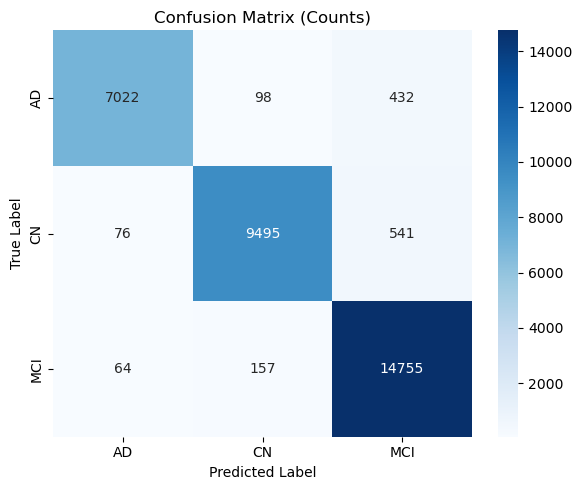

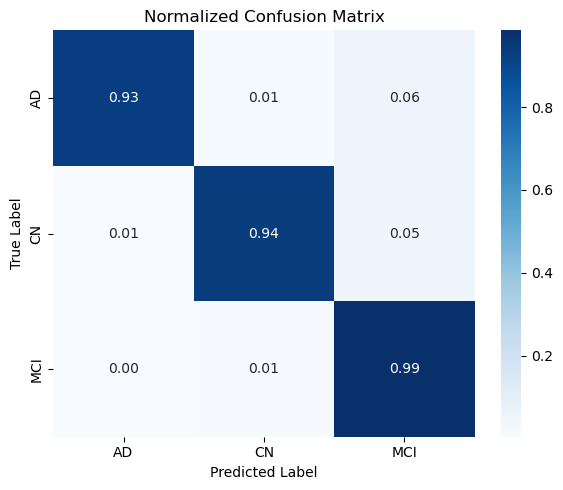

In [7]:
# ----------------------------
# 6. Confusion Matrix
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize by row

# Plotting
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Normalized version (for thesis clarity)
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [8]:
df_test = df[test_idx].copy()
df_test["predicted_class"] = le.inverse_transform(y_pred)

# Save CSV
df_test.to_csv("ResNet50_PCA_predictions.csv", index=False)


In [10]:
import pandas as pd

df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")
print(df.shape)
df.head()

(157312, 772)


,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,resnet_pca_9,...,resnet_pca_762,resnet_pca_763,resnet_pca_764,resnet_pca_765,resnet_pca_766,resnet_pca_767,filename,subject_id,class,subject_extracted
0,-24.189690,-25.203179,4.242370,5.083762,-8.445675,6.759305,1.008502,3.928269,-3.450274,-6.359534,...,0.108650,-0.734228,0.356423,0.279338,-0.092323,0.453436,002_S_0619_I118678_AD_slice_0079.png,2,AD,002_S_0619
1,-26.873774,-31.962256,11.545465,4.172281,-7.584505,8.217861,2.755282,3.193347,-2.890305,-4.986859,...,-0.174471,-0.488337,0.259158,-0.041902,-0.618470,-0.113307,002_S_0619_I118678_AD_slice_0080.png,2,AD,002_S_0619
2,-18.584409,-25.910656,2.631050,2.557537,-1.917162,4.861425,3.297774,3.425908,-2.209143,-3.078214,...,-0.489576,-0.416954,0.169212,-0.152016,-0.358901,0.334669,002_S_0619_I118678_AD_slice_0081.png,2,AD,002_S_0619
3,-13.114979,-21.325810,-3.793272,3.113940,1.296263,3.444136,2.668267,3.008887,-0.727794,-2.822743,...,0.064512,-0.819397,-0.117750,-0.211264,-0.286690,0.452900,002_S_0619_I118678_AD_slice_0082.png,2,AD,002_S_0619
4,-16.598942,-25.951100,2.158240,1.180876,-0.366550,4.019136,4.008902,2.528532,-2.322225,-2.034890,...,-0.158671,-0.515153,0.032196,-0.178579,-0.397371,0.206141,002_S_0619_I118678_AD_slice_0083.png,2,AD,002_S_0619


In [20]:
import pandas as pd

df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")
print(df.shape)
df.head()

(1464, 770)


,Subject,Group,medbert_0,medbert_1,medbert_2,medbert_3,medbert_4,medbert_5,medbert_6,medbert_7,...,medbert_758,medbert_759,medbert_760,medbert_761,medbert_762,medbert_763,medbert_764,medbert_765,medbert_766,medbert_767
0,941_S_1311,MCI,0.080227,-0.061472,0.529725,0.175582,0.134238,0.103919,-0.172209,-0.058271,...,-0.071016,-0.161694,-0.271816,0.185836,0.217798,0.050937,0.165142,0.019630,0.052318,-0.346020
1,941_S_1311,MCI,0.076382,-0.052141,0.528689,0.180919,0.127069,0.108636,-0.187786,-0.055698,...,-0.070843,-0.165284,-0.266288,0.177999,0.217958,0.049698,0.174034,0.020905,0.049233,-0.351850
2,941_S_1202,CN,0.077790,-0.058488,0.527280,0.164119,0.132354,0.103637,-0.163440,-0.053220,...,-0.069942,-0.157564,-0.258003,0.162636,0.207931,0.045207,0.162496,0.018787,0.044265,-0.334796
3,941_S_1202,CN,0.084684,-0.048429,0.539545,0.177149,0.141718,0.102119,-0.165956,-0.058740,...,-0.076610,-0.176693,-0.266327,0.170426,0.219437,0.059617,0.163065,0.007323,0.047776,-0.345088
4,941_S_1197,CN,0.061830,-0.046965,0.545425,0.171562,0.117961,0.079591,-0.150932,-0.071223,...,-0.071553,-0.165137,-0.281714,0.170120,0.217332,0.064951,0.152988,0.035432,0.055198,-0.350893


In [1]:
import pandas as pd

df = pd.read_csv("ResNet50_PCA_predictions.csv")
print(df.shape)
df.head()

(32640, 774)


,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,resnet_pca_9,...,resnet_pca_764,resnet_pca_765,resnet_pca_766,resnet_pca_767,filename,subject_id,class,subject_extracted,class_encoded,predicted_class
0,-19.158134,-21.266015,5.146417,0.070581,-5.338443,-1.055739,-4.831238,-1.736309,6.108043,-1.929876,...,0.174785,-0.484798,0.599334,-0.021817,002_S_0816_I118984_AD_slice_0087.png,2,AD,002_S_0816,0,AD
1,-10.862077,-21.205473,1.183302,0.761848,-0.732244,-0.590368,-2.963455,-1.562935,4.933937,-1.173954,...,0.440559,-0.261131,0.421916,-0.244005,002_S_0816_I118984_AD_slice_0088.png,2,AD,002_S_0816,0,AD
2,-13.845907,-22.149785,-1.203998,1.846348,-0.211214,-0.421820,-2.877450,-1.133631,5.049299,-1.172096,...,0.195349,-0.091586,0.469011,-0.226124,002_S_0816_I118984_AD_slice_0089.png,2,AD,002_S_0816,0,AD
3,-16.665867,-20.425049,-1.522003,3.418681,-2.040538,-1.586954,-2.131313,-1.222430,4.909238,-1.844141,...,0.189032,0.247588,0.767370,-0.276943,002_S_0816_I118984_AD_slice_0090.png,2,AD,002_S_0816,0,AD
4,-13.279621,-24.138505,0.180955,1.236132,1.845852,-1.921557,-1.175114,-1.501839,4.403385,-0.125050,...,0.388210,-0.261445,0.031115,-0.011433,002_S_0816_I118984_AD_slice_0091.png,2,AD,002_S_0816,0,AD


In [3]:

import pandas as pd

df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")
print(df.shape)
df.head()

(157312, 772)


,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,resnet_pca_9,...,resnet_pca_762,resnet_pca_763,resnet_pca_764,resnet_pca_765,resnet_pca_766,resnet_pca_767,filename,subject_id,class,subject_extracted
0,-24.189690,-25.203179,4.242370,5.083762,-8.445675,6.759305,1.008502,3.928269,-3.450274,-6.359534,...,0.108650,-0.734228,0.356423,0.279338,-0.092323,0.453436,002_S_0619_I118678_AD_slice_0079.png,2,AD,002_S_0619
1,-26.873774,-31.962256,11.545465,4.172281,-7.584505,8.217861,2.755282,3.193347,-2.890305,-4.986859,...,-0.174471,-0.488337,0.259158,-0.041902,-0.618470,-0.113307,002_S_0619_I118678_AD_slice_0080.png,2,AD,002_S_0619
2,-18.584409,-25.910656,2.631050,2.557537,-1.917162,4.861425,3.297774,3.425908,-2.209143,-3.078214,...,-0.489576,-0.416954,0.169212,-0.152016,-0.358901,0.334669,002_S_0619_I118678_AD_slice_0081.png,2,AD,002_S_0619
3,-13.114979,-21.325810,-3.793272,3.113940,1.296263,3.444136,2.668267,3.008887,-0.727794,-2.822743,...,0.064512,-0.819397,-0.117750,-0.211264,-0.286690,0.452900,002_S_0619_I118678_AD_slice_0082.png,2,AD,002_S_0619
4,-16.598942,-25.951100,2.158240,1.180876,-0.366550,4.019136,4.008902,2.528532,-2.322225,-2.034890,...,-0.158671,-0.515153,0.032196,-0.178579,-0.397371,0.206141,002_S_0619_I118678_AD_slice_0083.png,2,AD,002_S_0619


In [4]:
import pandas as pd

# Load your feature file
df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")

# Drop unnecessary columns
df = df.drop(columns=["filename", "subject_id"])

# Verify
print(df.columns)
print(df.shape)

# Save cleaned file
df.to_csv("ResNet50_PCA_768_clean.csv", index=False)

print("Saved file as ResNet50_PCA_768_clean.csv")


Index(['resnet_pca_0', 'resnet_pca_1', 'resnet_pca_2', 'resnet_pca_3',
       'resnet_pca_4', 'resnet_pca_5', 'resnet_pca_6', 'resnet_pca_7',
       'resnet_pca_8', 'resnet_pca_9',
       ...
       'resnet_pca_760', 'resnet_pca_761', 'resnet_pca_762', 'resnet_pca_763',
       'resnet_pca_764', 'resnet_pca_765', 'resnet_pca_766', 'resnet_pca_767',
       'class', 'subject_extracted'],
      dtype='object', length=770)
(157312, 770)
Saved file as ResNet50_PCA_768_clean.csv


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# 1. LOAD DATA
# =========================================================

resnet_path = "ResNet50_PCA_768_with_subject.csv"
bert_path   = "ADNI1_MedBERT_Embeddings.csv"

resnet_df = pd.read_csv(resnet_path)
bert_df   = pd.read_csv(bert_path)

print("ResNet shape (slice-level):", resnet_df.shape)
print("BERT shape (subject-level):", bert_df.shape)

# =========================================================
# 2. CLEAN & SELECT FEATURES
# =========================================================

# Drop unnecessary columns from ResNet
resnet_df = resnet_df.drop(columns=["filename", "subject_id"], errors="ignore")

# Select ResNet PCA feature columns
resnet_feat_cols = [c for c in resnet_df.columns if c.startswith("resnet_pca_")]

# Select MedBERT feature columns
bert_feat_cols = [c for c in bert_df.columns if c.startswith("medbert_")]

# =========================================================
# 3. AGGREGATE RESNET (SLICE → SUBJECT LEVEL)
# =========================================================

resnet_subject_df = (
    resnet_df
    .groupby("subject_extracted")[resnet_feat_cols]
    .mean()                         # MEAN POOLING
    .reset_index()
)

# Add class label per subject
labels_df = (
    resnet_df[["subject_extracted", "class"]]
    .drop_duplicates()
)

resnet_subject_df = resnet_subject_df.merge(
    labels_df,
    on="subject_extracted",
    how="left"
)

print("ResNet shape (subject-level):", resnet_subject_df.shape)

# =========================================================
# 4. ALIGN SUBJECT IDS (RESNET ↔ BERT)
# =========================================================

# Rename for consistency
bert_df = bert_df.rename(columns={"Subject": "subject_extracted",
                                  "Group": "class"})

common_subjects = set(resnet_subject_df["subject_extracted"]).intersection(
                  set(bert_df["subject_extracted"]))

print("Common subjects:", len(common_subjects))

resnet_subject_df = resnet_subject_df[
    resnet_subject_df["subject_extracted"].isin(common_subjects)
]

bert_df = bert_df[
    bert_df["subject_extracted"].isin(common_subjects)
]

# Sort for perfect alignment
resnet_subject_df = resnet_subject_df.sort_values("subject_extracted")
bert_df = bert_df.sort_values("subject_extracted")

# =========================================================
# 5. FUSION (FEATURE CONCATENATION)
# =========================================================

X_resnet = resnet_subject_df[resnet_feat_cols].values
X_bert   = bert_df[bert_feat_cols].values

X_fused = np.concatenate([X_resnet, X_bert], axis=1)

y = resnet_subject_df["class"].values

print("Fused feature shape:", X_fused.shape)

# =========================================================
# 6. LABEL ENCODING
# =========================================================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# =========================================================
# 7. SUBJECT-LEVEL TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_fused,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================================================
# 8. FEATURE SCALING
# =========================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# =========================================================
# 9. CLASSIFICATION
# =========================================================

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# =========================================================
# 10. EVALUATION
# =========================================================

acc = accuracy_score(y_test, y_pred)
report = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
)

print("\nAccuracy:", acc)
print("\nClassification Report:\n", report)

# =========================================================
# 11. SAVE FUSED DATASET (OPTIONAL)
# =========================================================

fused_df = pd.DataFrame(
    X_fused,
    columns=[f"resnet_{i}" for i in range(X_resnet.shape[1])] +
            [f"bert_{i}"   for i in range(X_bert.shape[1])]
)

fused_df["class"] = y
fused_df["subject_extracted"] = resnet_subject_df["subject_extracted"].values

fused_df.to_csv("Fused_ResNet_MedBERT_SubjectLevel.csv", index=False)

print("\nSaved: Fused_ResNet_MedBERT_SubjectLevel.csv")


ResNet shape (slice-level): (157312, 772)
BERT shape (subject-level): (1464, 770)
ResNet shape (subject-level): (637, 770)
Common subjects: 637


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 637 and the array at index 1 has size 1460

In [15]:
import pandas as pd
import numpy as np

# Load ResNet slice-level CSV
resnet_df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")
bert_df   = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# Drop unnecessary columns
resnet_df = resnet_df.drop(columns=["filename", "subject_id"], errors="ignore")

# Rename columns for consistency
resnet_df = resnet_df.rename(columns={"subject_extracted": "subject"})
bert_df   = bert_df.rename(columns={"Subject": "subject"})

# Aggregate slice-level ResNet features to subject-level
resnet_feat_cols = [c for c in resnet_df.columns if c.startswith("resnet_pca_")]
resnet_subject_df = resnet_df.groupby("subject")[resnet_feat_cols].mean().reset_index()

# ----------------------------
# Check shapes
# ----------------------------
print("ResNet subject-level shape:", resnet_subject_df.shape)
print("BERT shape:", bert_df.shape)


ResNet subject-level shape: (637, 769)
BERT shape: (1464, 770)


In [21]:
import pandas as pd
import numpy as np

# ----------------------------
# 1. Load CSVs
# ----------------------------
resnet_df = pd.read_csv("ResNet50_PCA_768_with_subject.csv")
bert_df   = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# ----------------------------
# 2. Drop unnecessary columns
# ----------------------------
resnet_df = resnet_df.drop(columns=["filename", "subject_id"], errors="ignore")

# Rename for consistency
resnet_df = resnet_df.rename(columns={"subject_extracted": "subject"})
bert_df   = bert_df.rename(columns={"Subject": "subject"})

# ----------------------------
# 3. Aggregate slice-level ResNet features per subject
# ----------------------------
resnet_feat_cols = [c for c in resnet_df.columns if c.startswith("resnet_pca_")]
resnet_subject_df = resnet_df.groupby("subject")[resnet_feat_cols].mean().reset_index()

# ----------------------------
# 4. Aggregate BERT features per subject (if multiple rows exist)
# ----------------------------
bert_feat_cols = [c for c in bert_df.columns if c.startswith("medbert_")]
bert_subject_df = bert_df.groupby("subject")[bert_feat_cols].mean().reset_index()

# ----------------------------
# 5. Keep only common subjects and sort
# ----------------------------
common_subjects = set(resnet_subject_df["subject"]) & set(bert_subject_df["subject"])
print("Common subjects:", len(common_subjects))

resnet_subject_df = resnet_subject_df[resnet_subject_df["subject"].isin(common_subjects)].sort_values("subject").reset_index(drop=True)
bert_subject_df   = bert_subject_df[bert_subject_df["subject"].isin(common_subjects)].sort_values("subject").reset_index(drop=True)

# ----------------------------
# 6. Select features
# ----------------------------
X_resnet = resnet_subject_df[resnet_feat_cols].values
X_bert   = bert_subject_df[bert_feat_cols].values

print("X_resnet shape:", X_resnet.shape)
print("X_bert shape  :", X_bert.shape)

# ----------------------------
# 7. Concatenate features
# ----------------------------
X_fused = np.concatenate([X_resnet, X_bert], axis=1)
print("Fused feature shape:", X_fused.shape)

# ----------------------------
# 8. Labels (from ResNet aggregated subject-level)
# ----------------------------
y = resnet_df.groupby("subject")["class"].first().loc[resnet_subject_df["subject"]].values
print("Labels shape:", y.shape)

# ----------------------------
# 9. Save fused features
# ----------------------------
fused_df = pd.DataFrame(X_fused, columns=[f"fused_{i}" for i in range(X_fused.shape[1])])
fused_df["subject"] = resnet_subject_df["subject"]
fused_df["class"]   = y
fused_df.to_csv("Fused_ResNet_BERT.csv", index=False)
print("Fused feature file saved!")


Common subjects: 637
X_resnet shape: (637, 768)
X_bert shape  : (637, 768)
Fused feature shape: (637, 1536)
Labels shape: (637,)
Fused feature file saved!


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# ----------------------------
# 1. Load fused data
# ----------------------------
fused_df = pd.read_csv("Fused_ResNet_BERT.csv")

X = fused_df[[c for c in fused_df.columns if c.startswith("fused_")]].values
y = fused_df["class"].values
subjects = fused_df["subject"].values

# ----------------------------
# 2. Subject-level split
# ----------------------------
unique_subjects = np.unique(subjects)
train_subj, test_subj = train_test_split(unique_subjects, test_size=0.2, random_state=42, stratify=None)

train_idx = fused_df["subject"].isin(train_subj)
test_idx  = fused_df["subject"].isin(test_subj)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ----------------------------
# 3. Train classifier
# ----------------------------
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# ----------------------------
# 4. Predict & evaluate
# ----------------------------
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

print("Classification Report:")
print(classification_report(y_test, y_pred))


Train shape: (509, 1536) Test shape: (128, 1536)
Test Accuracy: 0.84375
Classification Report:
              precision    recall  f1-score   support

          AD       1.00      0.52      0.68        27
          CN       0.81      0.78      0.79        32
         MCI       0.83      1.00      0.91        69

    accuracy                           0.84       128
   macro avg       0.88      0.77      0.79       128
weighted avg       0.86      0.84      0.83       128



In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# ----------------------------
# 1. Load fused data
# ----------------------------
fused_df = pd.read_csv("Fused_ResNet_BERT.csv")

# Features and labels
X = fused_df[[c for c in fused_df.columns if c.startswith("fused_")]].values
y = fused_df["class"].values
subjects = fused_df["subject"].values

# ----------------------------
# 2. Encode labels
# ----------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'AD','CN','MCI' -> 0,1,2
print("Classes:", le.classes_)

# ----------------------------
# 3. Subject-level split
# ----------------------------
unique_subjects = np.unique(subjects)
train_subj, test_subj = train_test_split(unique_subjects, test_size=0.2, random_state=42, stratify=None)

train_idx = fused_df["subject"].isin(train_subj)
test_idx  = fused_df["subject"].isin(test_subj)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ----------------------------
# 4. Train XGBoost
# ----------------------------
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)

# ----------------------------
# 5. Predict & evaluate
# ----------------------------
y_pred = xgb_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Classes: ['AD' 'CN' 'MCI']
Train shape: (509, 1536) Test shape: (128, 1536)


d:\Anaconda\envs\torch_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [02:09:19] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.9609375

Classification Report:
               precision    recall  f1-score   support

          AD       0.96      1.00      0.98        27
          CN       1.00      0.84      0.92        32
         MCI       0.95      1.00      0.97        69

    accuracy                           0.96       128
   macro avg       0.97      0.95      0.96       128
weighted avg       0.96      0.96      0.96       128



Classes: ['AD' 'CN' 'MCI']
Train shape: (509, 1536) Test shape: (128, 1536)


d:\Anaconda\envs\torch_gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [19:44:44] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.9609375

Classification Report:
               precision    recall  f1-score   support

          AD       0.96      1.00      0.98        27
          CN       1.00      0.84      0.92        32
         MCI       0.95      1.00      0.97        69

    accuracy                           0.96       128
   macro avg       0.97      0.95      0.96       128
weighted avg       0.96      0.96      0.96       128



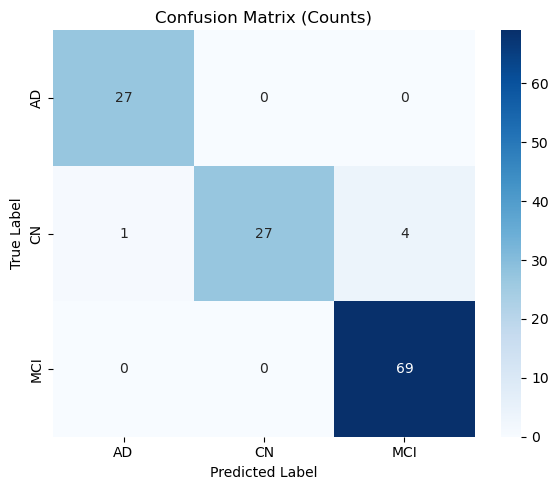

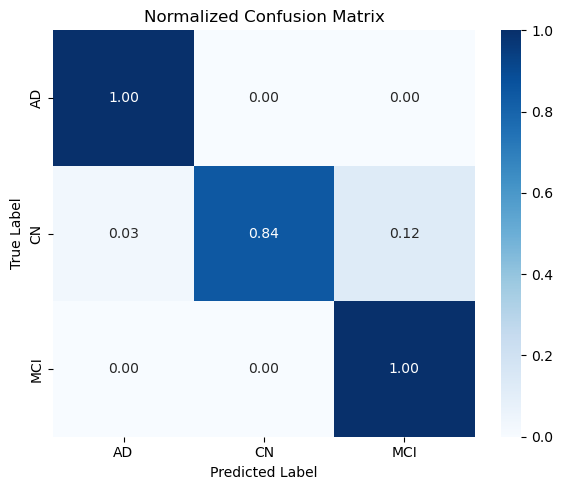

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# ----------------------------
# 1. Load fused data
# ----------------------------
fused_df = pd.read_csv("Fused_ResNet_BERT.csv")

# Features and labels
X = fused_df[[c for c in fused_df.columns if c.startswith("fused_")]].values
y = fused_df["class"].values
subjects = fused_df["subject"].values

# ----------------------------
# 2. Encode labels
# ----------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'AD','CN','MCI' -> 0,1,2
print("Classes:", le.classes_)

# ----------------------------
# 3. Subject-level split
# ----------------------------
unique_subjects = np.unique(subjects)
train_subj, test_subj = train_test_split(unique_subjects, test_size=0.2, random_state=42, stratify=None)

train_idx = fused_df["subject"].isin(train_subj)
test_idx  = fused_df["subject"].isin(test_subj)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ----------------------------
# 4. Train XGBoost
# ----------------------------
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)

# ----------------------------
# 5. Predict & evaluate
# ----------------------------
y_pred = xgb_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
# ----------------------------
# 6. Confusion Matrix
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize by row

# Plotting
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Normalized version (for thesis clarity)
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd

df = pd.read_csv("Fused_ResNet_BERT.csv")
print(df.shape)
df.head()

(637, 1538)


,fused_0,fused_1,fused_2,fused_3,fused_4,fused_5,fused_6,fused_7,fused_8,fused_9,...,fused_1528,fused_1529,fused_1530,fused_1531,fused_1532,fused_1533,fused_1534,fused_1535,subject,class
0,-16.464547,19.773259,0.038259,-0.763056,1.035391,0.969068,-2.173648,0.710298,-1.746397,0.225759,...,-0.263561,0.177067,0.222529,0.058989,0.167886,0.019808,0.035616,-0.345361,002_S_0295,CN
1,-16.606222,17.730109,-0.095277,-1.023483,0.189760,0.373146,-2.475419,-3.428771,0.672672,-0.904266,...,-0.282629,0.167424,0.220915,0.060090,0.156378,0.029460,0.049999,-0.349659,002_S_0413,CN
2,-17.577008,-23.744832,2.226827,-0.152158,-1.044133,3.080568,1.363516,3.586738,-2.383032,-3.014557,...,-0.261445,0.183658,0.228619,0.030618,0.175963,0.021191,0.044020,-0.334389,002_S_0619,AD
3,-15.828377,18.124493,-1.086019,-0.574586,0.581829,-0.743458,-1.685113,-1.975560,0.592815,-1.159326,...,-0.272759,0.185994,0.220300,0.051687,0.156757,0.013809,0.043380,-0.349847,002_S_0685,CN
4,3.812922,2.640430,-3.841059,4.649622,1.053920,0.717905,-3.703731,-2.481960,1.558077,-1.855128,...,-0.272773,0.165890,0.218755,0.058230,0.155670,0.020218,0.049586,-0.356009,002_S_0729,MCI


In [11]:
import pandas as pd

# MRI slice-level features
img_df = pd.read_csv("ResNet50_PCA_768_clean.csv")

# Text embeddings (subject-level)
text_df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")


In [12]:
# Rename for consistency
text_df = text_df.rename(columns={
    "Subject": "subject_extracted",
    "Group": "class"
})


In [13]:
fused_df = img_df.merge(
    text_df,
    on="subject_extracted",
    how="inner"
)

print(fused_df.shape)


(387200, 1539)


In [15]:
img_feats  = [c for c in fused_df.columns if c.startswith("resnet_pca_")]
text_feats = [c for c in fused_df.columns if c.startswith("medbert_")]

X = fused_df[img_feats + text_feats]
y = fused_df["class"]
subjects = fused_df["subject_extracted"]

print(X.shape)   # (n_slices, 1536)


KeyError: 'class'

In [16]:
print(fused_df.columns)


Index(['resnet_pca_0', 'resnet_pca_1', 'resnet_pca_2', 'resnet_pca_3',
       'resnet_pca_4', 'resnet_pca_5', 'resnet_pca_6', 'resnet_pca_7',
       'resnet_pca_8', 'resnet_pca_9',
       ...
       'medbert_758', 'medbert_759', 'medbert_760', 'medbert_761',
       'medbert_762', 'medbert_763', 'medbert_764', 'medbert_765',
       'medbert_766', 'medbert_767'],
      dtype='object', length=1539)


In [17]:
non_feature_cols = [
    c for c in fused_df.columns
    if not (c.startswith("resnet_pca_") or c.startswith("medbert_"))
]

print(non_feature_cols)


['class_x', 'subject_extracted', 'class_y']


In [18]:
# Verify consistency
(fused_df["class_x"] == fused_df["class_y"]).value_counts()


True    387200
Name: count, dtype: int64

In [19]:
fused_df = fused_df.drop(columns=["class_y"])
fused_df = fused_df.rename(columns={"class_x": "class"})


In [20]:
assert "class" in fused_df.columns
assert "subject_extracted" in fused_df.columns

print("✅ Label and subject columns are present")


✅ Label and subject columns are present


In [21]:
img_feats  = [c for c in fused_df.columns if c.startswith("resnet_pca_")]
text_feats = [c for c in fused_df.columns if c.startswith("medbert_")]

X = fused_df[img_feats + text_feats]
y = fused_df["class"]
subjects = fused_df["subject_extracted"]

print(X.shape)   # (157312, 1536)
print(y.shape)
print(subjects.shape)


(387200, 1536)
(387200,)
(387200,)


In [22]:
print(y.value_counts())
print(subjects.nunique())


class
MCI    174976
CN     121536
AD      90688
Name: count, dtype: int64
637


In [23]:
img_feats  = [c for c in fused_df.columns if c.startswith("resnet_pca_")]
text_feats = [c for c in fused_df.columns if c.startswith("medbert_")]

X = fused_df[img_feats + text_feats]
y = fused_df["class"]
subjects = fused_df["subject_extracted"]

print(X.shape)   # (n_slices, 1536)


(387200, 1536)


In [24]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    test_size=0.2,
    n_splits=1,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=subjects))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'AD': 0, 'CN': 1, 'MCI': 2}


In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_enc)

y_pred_enc = model.predict(X_test)

print("Slice-level Accuracy:", accuracy_score(y_test_enc, y_pred_enc))
print(classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=le.classes_
))


Slice-level Accuracy: 0.9631413532297629
              precision    recall  f1-score   support

          AD       0.98      0.97      0.98     22016
          CN       0.94      0.93      0.93     17088
         MCI       0.96      0.98      0.97     39168

    accuracy                           0.96     78272
   macro avg       0.96      0.96      0.96     78272
weighted avg       0.96      0.96      0.96     78272



In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


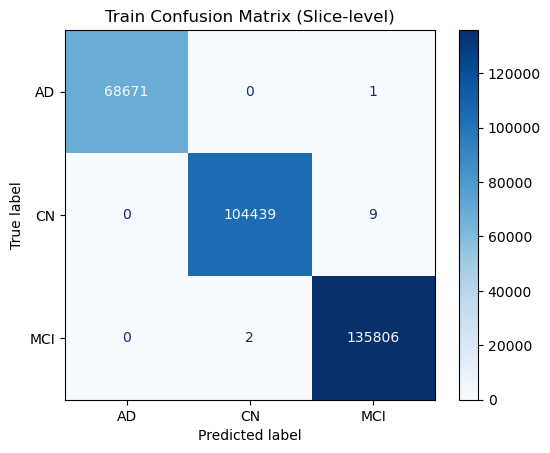

In [29]:
# Predict on TRAIN set
y_train_pred_enc = model.predict(X_train)

cm_train = confusion_matrix(y_train_enc, y_train_pred_enc)

disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=le.classes_
)

disp_train.plot(cmap="Blues", values_format="d")
plt.title("Train Confusion Matrix (Slice-level)")
plt.show()


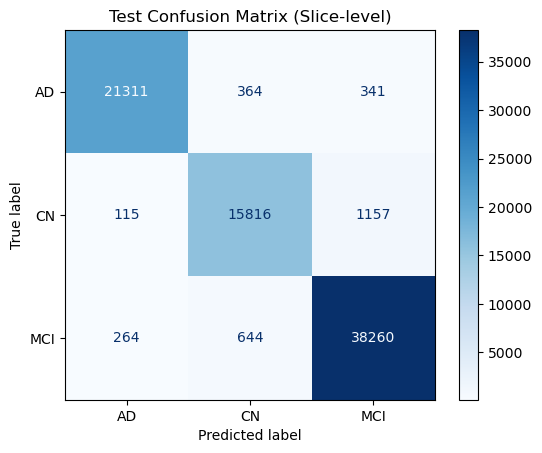

In [30]:
cm_test = confusion_matrix(y_test_enc, y_pred_enc)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=le.classes_
)

disp_test.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix (Slice-level)")
plt.show()


In [32]:
print("Train slices:", len(y_train_enc))
print("Test slices :", len(y_test_enc))
print("Test subjects:", subject_true.shape[0])


Train slices: 308928
Test slices : 78272
Test subjects: 128


In [33]:
from sklearn.metrics import accuracy_score

# Train predictions
y_train_pred_enc = model.predict(X_train)
train_acc = accuracy_score(y_train_enc, y_train_pred_enc)

# Test predictions (already computed)
test_acc = accuracy_score(y_test_enc, y_pred_enc)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)


Train Accuracy: 0.999961155997514
Test Accuracy : 0.9631413532297629


Class mapping: {'AD': 0, 'CN': 1, 'MCI': 2}

========== Fold 1 ==========
Train Accuracy: 1.0000, Test Accuracy: 0.5286


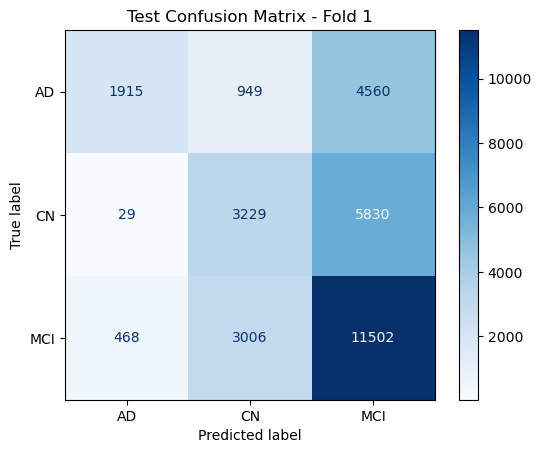


========== Fold 2 ==========
Train Accuracy: 1.0000, Test Accuracy: 0.6508


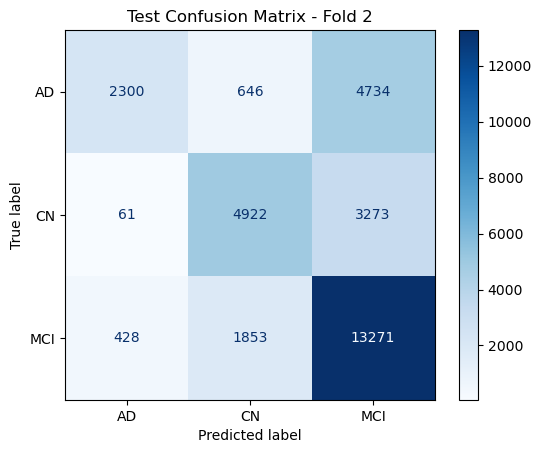


========== Fold 3 ==========
Train Accuracy: 1.0000, Test Accuracy: 0.5634


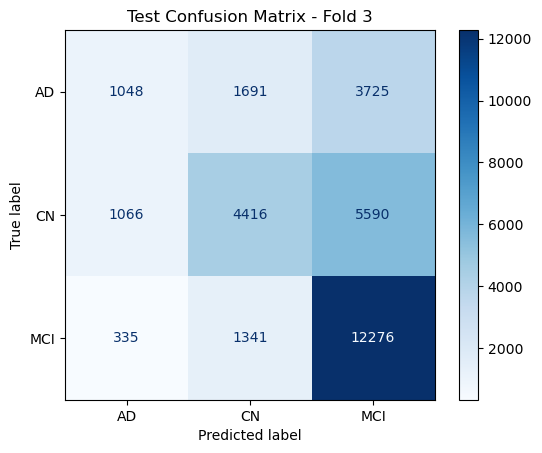


========== Fold 4 ==========
Train Accuracy: 1.0000, Test Accuracy: 0.5350


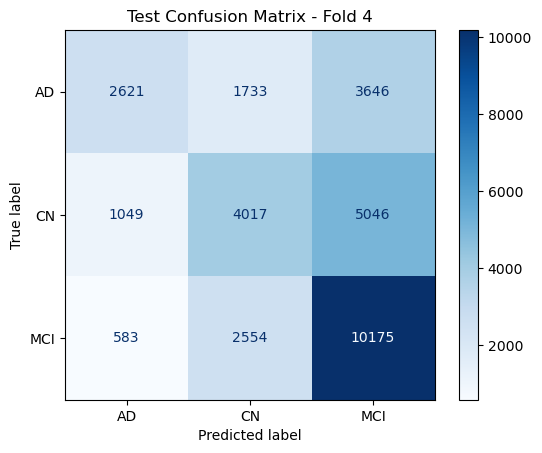


========== Fold 5 ==========
Train Accuracy: 1.0000, Test Accuracy: 0.6091


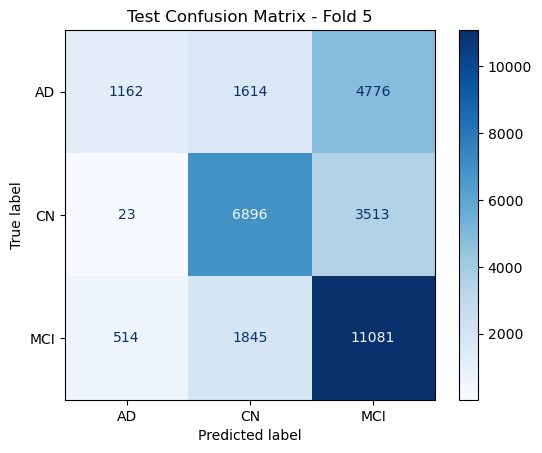


================ SLICE-LEVEL RESULTS ================
Slice-level Accuracy (mean over folds): 0.5773896214172173
Slice-level Classification Report:
              precision    recall  f1-score   support

          AD       0.67      0.24      0.36     37120
          CN       0.58      0.48      0.52     48960
         MCI       0.57      0.82      0.67     71232

    accuracy                           0.58    157312
   macro avg       0.60      0.51      0.52    157312
weighted avg       0.59      0.58      0.55    157312


================ SUBJECT-LEVEL RESULTS ================
Subject-level Accuracy: 0.598116169544741
Subject-level Classification Report:
              precision    recall  f1-score   support

          AD       0.65      0.26      0.37       133
          CN       0.57      0.46      0.51       193
         MCI       0.60      0.83      0.70       311

    accuracy                           0.60       637
   macro avg       0.61      0.52      0.53       637
weighted

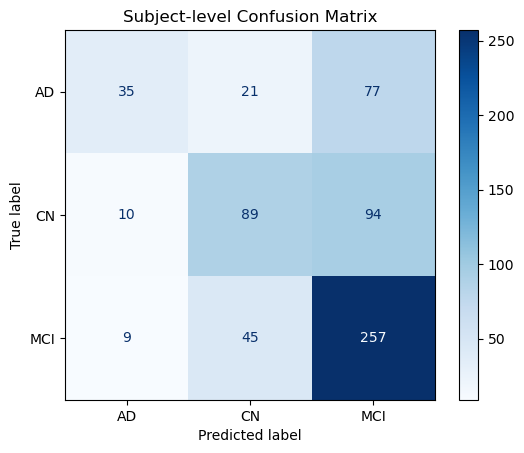

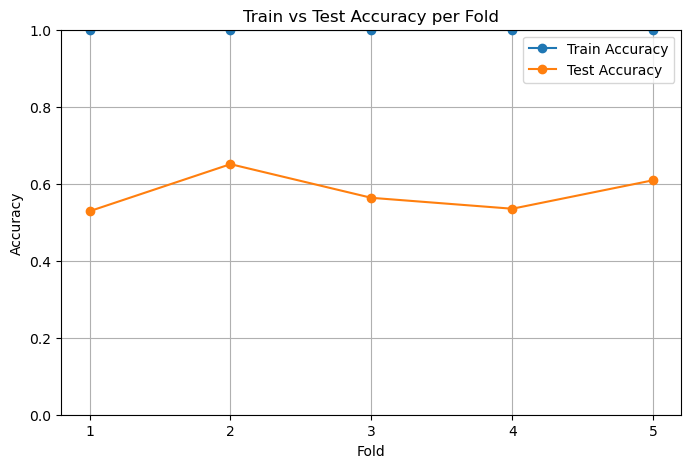

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# 1. Load MRI and MedBERT features
# ------------------------------------------------------------
img_df = pd.read_csv("ResNet50_PCA_768_clean.csv")
text_df = pd.read_csv("ADNI1_MedBERT_Embeddings.csv")

# ------------------------------------------------------------
# 2. Convert to float32 to save memory
# ------------------------------------------------------------
img_feats  = [c for c in img_df.columns if c.startswith("resnet_pca_")]
img_df[img_feats] = img_df[img_feats].astype(np.float32)

text_feats = [c for c in text_df.columns if c.startswith("medbert_")]
text_df[text_feats] = text_df[text_feats].astype(np.float32)

# ------------------------------------------------------------
# 3. Prepare label & subject columns
# ------------------------------------------------------------
text_df = text_df.rename(columns={"Subject": "subject_extracted", "Group": "class"})
subjects = img_df["subject_extracted"]
y = img_df["class"]

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ------------------------------------------------------------
# 4. Subject-wise 5-fold cross-validation
# ------------------------------------------------------------
gkf = GroupKFold(n_splits=5)

all_slice_true = []
all_slice_pred = []

subject_true_all = []
subject_pred_all = []

train_acc_list = []
test_acc_list = []

for fold, (train_idx, test_idx) in enumerate(
        gkf.split(img_df, y_enc, groups=subjects), 1):

    print(f"\n========== Fold {fold} ==========")

    # Split slices
    X_train_slices = img_df.iloc[train_idx]
    X_test_slices  = img_df.iloc[test_idx]

    y_train = y_enc[train_idx]
    y_test  = y_enc[test_idx]

    # Map MedBERT embeddings per slice (on-the-fly)
    def map_medbert(df_slices):
        medbert_arr = np.zeros((len(df_slices), len(text_feats)), dtype=np.float32)
        for i, subj in enumerate(df_slices["subject_extracted"]):
            emb_row = text_df[text_df["subject_extracted"]==subj][text_feats].values
            # Some subjects have multiple rows? take first
            medbert_arr[i] = emb_row[0]
        return np.hstack([df_slices[img_feats].values.astype(np.float32), medbert_arr])

    X_train = map_medbert(X_train_slices)
    X_test  = map_medbert(X_test_slices)

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )

    rf.fit(X_train, y_train)

    # ---------- Predictions ----------
    y_train_pred = rf.predict(X_train)
    y_test_pred  = rf.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

    all_slice_true.extend(y_test)
    all_slice_pred.extend(y_test_pred)

    # ---------- Slice-level Confusion Matrix ----------
    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(cm_test, display_labels=le.classes_)
    disp_test.plot(cmap="Blues", values_format="d")
    plt.title(f"Test Confusion Matrix - Fold {fold}")
    plt.show()

    # ---------- Subject-level aggregation ----------
    df_test = X_test_slices.copy()
    df_test["y_true"] = y_test
    df_test["y_pred"] = y_test_pred

    subj_pred = df_test.groupby("subject_extracted")["y_pred"].agg(lambda x: np.bincount(x).argmax())
    subj_true = df_test.groupby("subject_extracted")["y_true"].first()

    subject_true_all.extend(subj_true)
    subject_pred_all.extend(subj_pred)

# ------------------------------------------------------------
# 5. Final Results
# ------------------------------------------------------------
print("\n================ SLICE-LEVEL RESULTS ================")
print("Slice-level Accuracy (mean over folds):", np.mean(test_acc_list))
print("Slice-level Classification Report:")
print(classification_report(all_slice_true, all_slice_pred, target_names=le.classes_))

print("\n================ SUBJECT-LEVEL RESULTS ================")
print("Subject-level Accuracy:", accuracy_score(subject_true_all, subject_pred_all))
print("Subject-level Classification Report:")
print(classification_report(subject_true_all, subject_pred_all, target_names=le.classes_))

# Subject-level confusion matrix
cm_subject = confusion_matrix(subject_true_all, subject_pred_all)
disp_subject = ConfusionMatrixDisplay(cm_subject, display_labels=le.classes_)
disp_subject.plot(cmap="Blues", values_format="d")
plt.title("Subject-level Confusion Matrix")
plt.show()

# Train vs Test Accuracy plot per fold
plt.figure(figsize=(8,5))
plt.plot(range(1,6), train_acc_list, marker='o', label='Train Accuracy')
plt.plot(range(1,6), test_acc_list, marker='o', label='Test Accuracy')
plt.xticks(range(1,6))
plt.ylim(0,1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy per Fold")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import os
import torch
import torch.nn as nn
import numpy as np
import cv2
from tqdm import tqdm
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================
# CONFIG
# ==========================
data_dir = r"D:\coronal_slices_filtered_flattened\test"   # AD / CN / MCI
model_path = r"D:\checkpoints_full\efficientnet_b0_best.pth"

output_mis = "misclassified_AD_Efficient_gradcam"
output_correct = "correct_AD_Efficient_gradcam"

batch_size = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(os.path.join(output_mis, "side_by_side"), exist_ok=True)
os.makedirs(os.path.join(output_correct, "side_by_side"), exist_ok=True)

# ==========================
# MODEL DEFINITION (EfficientNet-B0)
# ==========================
class MRIClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        self.backbone.classifier[1] = nn.Linear(
            self.backbone.classifier[1].in_features,
            num_classes
        )

    def forward(self, x):
        return self.backbone(x)

# ==========================
# LOAD MODEL
# ==========================
model = MRIClassifier(num_classes=3)
#state_dict = torch.load(model_path, map_location=device)
#model.load_state_dict(state_dict)
state_dict = torch.load(model_path, map_location=device)
model.backbone.load_state_dict(state_dict)

model.to(device)
model.eval()

# ==========================
# DATA LOADER
# ==========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

# ==========================
# GRAD-CAM++ SETUP (EfficientNet)
# ==========================
target_layers = [model.backbone.features[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers,
    
)


total_focus_ratio = []
correct = 0
misclassified = 0

# ==========================
# GRAD-CAM LOOP
# ==========================
for i, (img, label) in enumerate(tqdm(loader, desc="Generating Grad-CAM++")):
    img = img.to(device)
    label = label.to(device)

    img.requires_grad_()

    outputs = model(img)
    preds = outputs.argmax(dim=1)

    # --------------------------
    # Recover RGB image
    # --------------------------
    rgb_img = img[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb_img = np.clip(
        rgb_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406],
        0, 1
    )

    # --------------------------
    # Grad-CAM++
    # --------------------------
    grayscale_cam = cam(input_tensor=img)[0]

    # --------------------------
    # Hippocampal ROI (Approx.)
    # --------------------------
    h, w = grayscale_cam.shape
    hippocampus_mask = np.zeros((h, w), dtype=np.float32)

    x1, x2 = int(w * 0.35), int(w * 0.65)
    y1, y2 = int(h * 0.55), int(h * 0.85)
    hippocampus_mask[y1:y2, x1:x2] = 1.0

    masked_cam = grayscale_cam * hippocampus_mask
    masked_cam /= (masked_cam.max() + 1e-8)

    focus_ratio = masked_cam.sum() / (grayscale_cam.sum() + 1e-8)
    total_focus_ratio.append(focus_ratio)

    # --------------------------
    # Visualization
    # --------------------------
    vis_full = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    vis_roi = show_cam_on_image(rgb_img, masked_cam, use_rgb=True)

    rgb_cv = (rgb_img * 255).astype(np.uint8)[:, :, ::-1]
    vis_full = vis_full[:, :, ::-1]
    vis_roi = vis_roi[:, :, ::-1]

    side_by_side = np.hstack([rgb_cv, vis_full, vis_roi])

    fname = os.path.basename(dataset.samples[i][0])

    is_correct = preds.item() == label.item()
    save_dir = output_correct if is_correct else output_mis

    save_path = os.path.join(
        save_dir,
        "side_by_side",
        f"{fname}_pred{idx_to_class[preds.item()]}_true{idx_to_class[label.item()]}.jpg"
    )

    cv2.imwrite(save_path, side_by_side)

    if is_correct:
        correct += 1
    else:
        misclassified += 1

    print(f"{fname} → Hippocampal focus: {focus_ratio:.2%}")

# ==========================
# SUMMARY
# ==========================
print("\n================ SUMMARY ================")
print(f"Correct       : {correct}")
print(f"Misclassified : {misclassified}")
print(f"Avg Hippo Focus Ratio: {np.mean(total_focus_ratio):.2%}")
print(f"Saved to:\n{output_correct}/side_by_side\n{output_mis}/side_by_side")


Generating Grad-CAM++:   0%|          | 2/21248 [00:01<4:10:15,  1.41it/s]

002_S_0816_I92146_AD_slice_0074.png → Hippocampal focus: 23.37%
002_S_0816_I92146_AD_slice_0075.png → Hippocampal focus: 26.05%


Generating Grad-CAM++:   0%|          | 5/21248 [00:01<1:22:18,  4.30it/s]

002_S_0816_I92146_AD_slice_0076.png → Hippocampal focus: 19.25%
002_S_0816_I92146_AD_slice_0077.png → Hippocampal focus: 17.56%
002_S_0816_I92146_AD_slice_0078.png → Hippocampal focus: 17.55%


Generating Grad-CAM++:   0%|          | 7/21248 [00:02<56:08,  6.31it/s]  

002_S_0816_I92146_AD_slice_0079.png → Hippocampal focus: 28.82%
002_S_0816_I92146_AD_slice_0080.png → Hippocampal focus: 17.59%
002_S_0816_I92146_AD_slice_0081.png → Hippocampal focus: 19.72%


Generating Grad-CAM++:   0%|          | 11/21248 [00:02<37:08,  9.53it/s]

002_S_0816_I92146_AD_slice_0082.png → Hippocampal focus: 17.92%
002_S_0816_I92146_AD_slice_0083.png → Hippocampal focus: 18.14%
002_S_0816_I92146_AD_slice_0084.png → Hippocampal focus: 17.94%


Generating Grad-CAM++:   0%|          | 13/21248 [00:02<35:19, 10.02it/s]

002_S_0816_I92146_AD_slice_0085.png → Hippocampal focus: 19.10%
002_S_0816_I92146_AD_slice_0086.png → Hippocampal focus: 18.84%
002_S_0816_I92146_AD_slice_0087.png → Hippocampal focus: 15.59%


Generating Grad-CAM++:   0%|          | 17/21248 [00:02<32:51, 10.77it/s]

002_S_0816_I92146_AD_slice_0088.png → Hippocampal focus: 17.26%
002_S_0816_I92146_AD_slice_0089.png → Hippocampal focus: 35.51%
002_S_0816_I92146_AD_slice_0090.png → Hippocampal focus: 37.26%


Generating Grad-CAM++:   0%|          | 19/21248 [00:03<31:13, 11.33it/s]

002_S_0816_I92146_AD_slice_0091.png → Hippocampal focus: 20.85%
002_S_0816_I92146_AD_slice_0092.png → Hippocampal focus: 20.78%
002_S_0816_I92146_AD_slice_0093.png → Hippocampal focus: 23.59%


Generating Grad-CAM++:   0%|          | 23/21248 [00:03<31:00, 11.41it/s]

002_S_0816_I92146_AD_slice_0094.png → Hippocampal focus: 34.54%
002_S_0816_I92146_AD_slice_0095.png → Hippocampal focus: 27.94%
002_S_0816_I92146_AD_slice_0096.png → Hippocampal focus: 26.43%


Generating Grad-CAM++:   0%|          | 25/21248 [00:03<30:42, 11.52it/s]

002_S_0816_I92146_AD_slice_0097.png → Hippocampal focus: 28.44%
002_S_0816_I92146_AD_slice_0098.png → Hippocampal focus: 29.20%


Generating Grad-CAM++:   0%|          | 27/21248 [00:03<30:02, 11.77it/s]

002_S_0816_I92146_AD_slice_0099.png → Hippocampal focus: 27.73%
002_S_0816_I92146_AD_slice_0100.png → Hippocampal focus: 22.93%
002_S_0816_I92146_AD_slice_0101.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:   0%|          | 31/21248 [00:04<31:14, 11.32it/s]

002_S_0816_I92146_AD_slice_0102.png → Hippocampal focus: 25.65%
002_S_0816_I92146_AD_slice_0103.png → Hippocampal focus: 26.57%
002_S_0816_I92146_AD_slice_0104.png → Hippocampal focus: 27.11%


Generating Grad-CAM++:   0%|          | 33/21248 [00:04<31:47, 11.12it/s]

002_S_0816_I92146_AD_slice_0105.png → Hippocampal focus: 27.29%
002_S_0816_I92146_AD_slice_0106.png → Hippocampal focus: 27.71%
002_S_0816_I92146_AD_slice_0107.png → Hippocampal focus: 25.97%


Generating Grad-CAM++:   0%|          | 37/21248 [00:04<29:14, 12.09it/s]

002_S_0816_I92146_AD_slice_0108.png → Hippocampal focus: 15.32%
002_S_0816_I92146_AD_slice_0109.png → Hippocampal focus: 26.07%
002_S_0816_I92146_AD_slice_0110.png → Hippocampal focus: 26.64%


Generating Grad-CAM++:   0%|          | 39/21248 [00:04<27:57, 12.64it/s]

002_S_0816_I92146_AD_slice_0111.png → Hippocampal focus: 20.03%
002_S_0816_I92146_AD_slice_0112.png → Hippocampal focus: 26.68%
002_S_0816_I92146_AD_slice_0113.png → Hippocampal focus: 22.94%


Generating Grad-CAM++:   0%|          | 43/21248 [00:05<30:46, 11.49it/s]

002_S_0816_I92146_AD_slice_0114.png → Hippocampal focus: 20.61%
002_S_0816_I92146_AD_slice_0115.png → Hippocampal focus: 20.52%
002_S_0816_I92146_AD_slice_0116.png → Hippocampal focus: 18.12%


Generating Grad-CAM++:   0%|          | 45/21248 [00:05<31:06, 11.36it/s]

002_S_0816_I92146_AD_slice_0117.png → Hippocampal focus: 19.34%
002_S_0816_I92146_AD_slice_0118.png → Hippocampal focus: 20.52%
002_S_0816_I92146_AD_slice_0119.png → Hippocampal focus: 20.90%


Generating Grad-CAM++:   0%|          | 49/21248 [00:05<31:36, 11.18it/s]

002_S_0816_I92146_AD_slice_0120.png → Hippocampal focus: 22.14%
002_S_0816_I92146_AD_slice_0121.png → Hippocampal focus: 21.30%
002_S_0816_I92146_AD_slice_0122.png → Hippocampal focus: 22.57%


Generating Grad-CAM++:   0%|          | 51/21248 [00:05<31:52, 11.08it/s]

002_S_0816_I92146_AD_slice_0123.png → Hippocampal focus: 22.08%
002_S_0816_I92146_AD_slice_0124.png → Hippocampal focus: 25.57%
002_S_0816_I92146_AD_slice_0125.png → Hippocampal focus: 25.14%


Generating Grad-CAM++:   0%|          | 55/21248 [00:06<31:50, 11.09it/s]

002_S_0816_I92146_AD_slice_0126.png → Hippocampal focus: 23.90%
002_S_0816_I92146_AD_slice_0127.png → Hippocampal focus: 22.55%
002_S_0816_I92146_AD_slice_0128.png → Hippocampal focus: 23.91%


Generating Grad-CAM++:   0%|          | 57/21248 [00:06<33:06, 10.67it/s]

002_S_0816_I92146_AD_slice_0129.png → Hippocampal focus: 23.05%
002_S_0816_I92146_AD_slice_0130.png → Hippocampal focus: 25.95%
002_S_0816_I92146_AD_slice_0131.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:   0%|          | 61/21248 [00:06<31:51, 11.08it/s]

002_S_0816_I92146_AD_slice_0132.png → Hippocampal focus: 29.46%
002_S_0816_I92146_AD_slice_0133.png → Hippocampal focus: 26.55%
002_S_0816_I92146_AD_slice_0134.png → Hippocampal focus: 31.70%


Generating Grad-CAM++:   0%|          | 63/21248 [00:06<30:52, 11.44it/s]

002_S_0816_I92146_AD_slice_0135.png → Hippocampal focus: 18.19%
002_S_0816_I92146_AD_slice_0136.png → Hippocampal focus: 15.66%
002_S_0816_I92146_AD_slice_0137.png → Hippocampal focus: 14.58%


Generating Grad-CAM++:   0%|          | 67/21248 [00:07<30:51, 11.44it/s]

006_S_0547_I78722_AD_slice_0100.png → Hippocampal focus: 27.98%
006_S_0547_I78722_AD_slice_0101.png → Hippocampal focus: 27.23%
006_S_0547_I78722_AD_slice_0102.png → Hippocampal focus: 25.23%


Generating Grad-CAM++:   0%|          | 69/21248 [00:07<31:18, 11.27it/s]

006_S_0547_I78722_AD_slice_0103.png → Hippocampal focus: 24.68%
006_S_0547_I78722_AD_slice_0104.png → Hippocampal focus: 25.03%
006_S_0547_I78722_AD_slice_0105.png → Hippocampal focus: 24.01%


Generating Grad-CAM++:   0%|          | 71/21248 [00:07<32:05, 11.00it/s]

006_S_0547_I78722_AD_slice_0106.png → Hippocampal focus: 27.24%
006_S_0547_I78722_AD_slice_0107.png → Hippocampal focus: 25.91%


Generating Grad-CAM++:   0%|          | 75/21248 [00:08<32:17, 10.93it/s]

006_S_0547_I78722_AD_slice_0108.png → Hippocampal focus: 24.32%
006_S_0547_I78722_AD_slice_0109.png → Hippocampal focus: 24.42%
006_S_0547_I78722_AD_slice_0110.png → Hippocampal focus: 20.06%


Generating Grad-CAM++:   0%|          | 77/21248 [00:08<31:02, 11.37it/s]

006_S_0547_I78722_AD_slice_0111.png → Hippocampal focus: 21.01%
006_S_0547_I78722_AD_slice_0112.png → Hippocampal focus: 22.39%
006_S_0547_I78722_AD_slice_0113.png → Hippocampal focus: 25.66%


Generating Grad-CAM++:   0%|          | 81/21248 [00:08<31:34, 11.18it/s]

006_S_0547_I78722_AD_slice_0114.png → Hippocampal focus: 19.92%
006_S_0547_I78722_AD_slice_0115.png → Hippocampal focus: 20.36%
006_S_0547_I78722_AD_slice_0116.png → Hippocampal focus: 20.86%


Generating Grad-CAM++:   0%|          | 83/21248 [00:08<30:03, 11.74it/s]

006_S_0547_I78722_AD_slice_0117.png → Hippocampal focus: 20.27%
006_S_0547_I78722_AD_slice_0118.png → Hippocampal focus: 20.47%
006_S_0547_I78722_AD_slice_0119.png → Hippocampal focus: 21.06%


Generating Grad-CAM++:   0%|          | 87/21248 [00:09<29:55, 11.78it/s]

006_S_0547_I78722_AD_slice_0120.png → Hippocampal focus: 21.33%
006_S_0547_I78722_AD_slice_0121.png → Hippocampal focus: 24.06%
006_S_0547_I78722_AD_slice_0122.png → Hippocampal focus: 21.01%


Generating Grad-CAM++:   0%|          | 89/21248 [00:09<27:58, 12.60it/s]

006_S_0547_I78722_AD_slice_0123.png → Hippocampal focus: 21.49%
006_S_0547_I78722_AD_slice_0124.png → Hippocampal focus: 21.38%
006_S_0547_I78722_AD_slice_0125.png → Hippocampal focus: 26.74%
006_S_0547_I78722_AD_slice_0126.png → Hippocampal focus: 22.46%


Generating Grad-CAM++:   0%|          | 93/21248 [00:09<25:58, 13.57it/s]

006_S_0547_I78722_AD_slice_0127.png → Hippocampal focus: 22.67%
006_S_0547_I78722_AD_slice_0128.png → Hippocampal focus: 24.28%
006_S_0547_I78722_AD_slice_0129.png → Hippocampal focus: 19.34%


Generating Grad-CAM++:   0%|          | 95/21248 [00:09<27:09, 12.98it/s]

006_S_0547_I78722_AD_slice_0130.png → Hippocampal focus: 20.94%
006_S_0547_I78722_AD_slice_0131.png → Hippocampal focus: 24.20%


Generating Grad-CAM++:   0%|          | 99/21248 [00:09<28:50, 12.22it/s]

006_S_0547_I78722_AD_slice_0132.png → Hippocampal focus: 25.89%
006_S_0547_I78722_AD_slice_0133.png → Hippocampal focus: 26.27%
006_S_0547_I78722_AD_slice_0134.png → Hippocampal focus: 27.84%


Generating Grad-CAM++:   0%|          | 101/21248 [00:10<28:33, 12.34it/s]

006_S_0547_I78722_AD_slice_0135.png → Hippocampal focus: 33.58%
006_S_0547_I78722_AD_slice_0136.png → Hippocampal focus: 25.47%
006_S_0547_I78722_AD_slice_0137.png → Hippocampal focus: 23.36%


Generating Grad-CAM++:   0%|          | 105/21248 [00:10<29:31, 11.94it/s]

006_S_0547_I78722_AD_slice_0138.png → Hippocampal focus: 24.55%
006_S_0547_I78722_AD_slice_0139.png → Hippocampal focus: 24.06%
006_S_0547_I78722_AD_slice_0140.png → Hippocampal focus: 23.85%


Generating Grad-CAM++:   1%|          | 107/21248 [00:10<31:42, 11.11it/s]

006_S_0547_I78722_AD_slice_0141.png → Hippocampal focus: 26.44%
006_S_0547_I78722_AD_slice_0142.png → Hippocampal focus: 24.77%
006_S_0547_I78722_AD_slice_0143.png → Hippocampal focus: 24.44%


Generating Grad-CAM++:   1%|          | 111/21248 [00:11<31:37, 11.14it/s]

006_S_0547_I78722_AD_slice_0144.png → Hippocampal focus: 21.48%
006_S_0547_I78722_AD_slice_0145.png → Hippocampal focus: 21.46%
006_S_0547_I78722_AD_slice_0146.png → Hippocampal focus: 18.99%


Generating Grad-CAM++:   1%|          | 113/21248 [00:11<30:26, 11.57it/s]

006_S_0547_I78722_AD_slice_0147.png → Hippocampal focus: 22.11%
006_S_0547_I78722_AD_slice_0148.png → Hippocampal focus: 19.59%
006_S_0547_I78722_AD_slice_0149.png → Hippocampal focus: 21.31%


Generating Grad-CAM++:   1%|          | 117/21248 [00:11<30:28, 11.56it/s]

006_S_0547_I78722_AD_slice_0150.png → Hippocampal focus: 24.77%
006_S_0547_I78722_AD_slice_0151.png → Hippocampal focus: 21.74%
006_S_0547_I78722_AD_slice_0152.png → Hippocampal focus: 27.12%


Generating Grad-CAM++:   1%|          | 119/21248 [00:11<30:37, 11.50it/s]

006_S_0547_I78722_AD_slice_0153.png → Hippocampal focus: 28.26%
006_S_0547_I78722_AD_slice_0154.png → Hippocampal focus: 26.99%
006_S_0547_I78722_AD_slice_0155.png → Hippocampal focus: 23.81%


Generating Grad-CAM++:   1%|          | 123/21248 [00:12<31:26, 11.20it/s]

006_S_0547_I78722_AD_slice_0156.png → Hippocampal focus: 26.84%
006_S_0547_I78722_AD_slice_0157.png → Hippocampal focus: 34.60%
006_S_0547_I78722_AD_slice_0158.png → Hippocampal focus: 22.99%


Generating Grad-CAM++:   1%|          | 125/21248 [00:12<31:20, 11.23it/s]

006_S_0547_I78722_AD_slice_0159.png → Hippocampal focus: 21.43%
006_S_0547_I78722_AD_slice_0160.png → Hippocampal focus: 20.77%
006_S_0547_I78722_AD_slice_0161.png → Hippocampal focus: 20.95%


Generating Grad-CAM++:   1%|          | 129/21248 [00:12<30:41, 11.47it/s]

006_S_0547_I78722_AD_slice_0162.png → Hippocampal focus: 23.88%
006_S_0547_I78722_AD_slice_0163.png → Hippocampal focus: 19.37%
007_S_0316_I36573_AD_slice_0097.png → Hippocampal focus: 30.24%


Generating Grad-CAM++:   1%|          | 131/21248 [00:12<30:38, 11.49it/s]

007_S_0316_I36573_AD_slice_0098.png → Hippocampal focus: 30.65%
007_S_0316_I36573_AD_slice_0099.png → Hippocampal focus: 29.47%
007_S_0316_I36573_AD_slice_0100.png → Hippocampal focus: 29.25%


Generating Grad-CAM++:   1%|          | 135/21248 [00:13<29:57, 11.75it/s]

007_S_0316_I36573_AD_slice_0101.png → Hippocampal focus: 29.00%
007_S_0316_I36573_AD_slice_0102.png → Hippocampal focus: 14.67%
007_S_0316_I36573_AD_slice_0103.png → Hippocampal focus: 28.01%


Generating Grad-CAM++:   1%|          | 137/21248 [00:13<30:46, 11.44it/s]

007_S_0316_I36573_AD_slice_0104.png → Hippocampal focus: 13.29%
007_S_0316_I36573_AD_slice_0105.png → Hippocampal focus: 16.71%


Generating Grad-CAM++:   1%|          | 139/21248 [00:13<32:22, 10.87it/s]

007_S_0316_I36573_AD_slice_0106.png → Hippocampal focus: 17.37%
007_S_0316_I36573_AD_slice_0107.png → Hippocampal focus: 17.93%
007_S_0316_I36573_AD_slice_0108.png → Hippocampal focus: 18.98%


Generating Grad-CAM++:   1%|          | 143/21248 [00:13<30:37, 11.48it/s]

007_S_0316_I36573_AD_slice_0109.png → Hippocampal focus: 26.67%
007_S_0316_I36573_AD_slice_0110.png → Hippocampal focus: 17.78%
007_S_0316_I36573_AD_slice_0111.png → Hippocampal focus: 31.79%


Generating Grad-CAM++:   1%|          | 145/21248 [00:14<31:51, 11.04it/s]

007_S_0316_I36573_AD_slice_0112.png → Hippocampal focus: 32.49%
007_S_0316_I36573_AD_slice_0113.png → Hippocampal focus: 32.23%
007_S_0316_I36573_AD_slice_0114.png → Hippocampal focus: 30.23%


Generating Grad-CAM++:   1%|          | 149/21248 [00:14<31:50, 11.05it/s]

007_S_0316_I36573_AD_slice_0115.png → Hippocampal focus: 27.57%
007_S_0316_I36573_AD_slice_0116.png → Hippocampal focus: 27.02%
007_S_0316_I36573_AD_slice_0117.png → Hippocampal focus: 27.65%


Generating Grad-CAM++:   1%|          | 151/21248 [00:14<31:39, 11.11it/s]

007_S_0316_I36573_AD_slice_0118.png → Hippocampal focus: 27.09%
007_S_0316_I36573_AD_slice_0119.png → Hippocampal focus: 25.84%
007_S_0316_I36573_AD_slice_0120.png → Hippocampal focus: 24.42%


Generating Grad-CAM++:   1%|          | 155/21248 [00:14<31:10, 11.28it/s]

007_S_0316_I36573_AD_slice_0121.png → Hippocampal focus: 24.61%
007_S_0316_I36573_AD_slice_0122.png → Hippocampal focus: 29.90%
007_S_0316_I36573_AD_slice_0123.png → Hippocampal focus: 23.49%


Generating Grad-CAM++:   1%|          | 157/21248 [00:15<30:45, 11.43it/s]

007_S_0316_I36573_AD_slice_0124.png → Hippocampal focus: 22.76%
007_S_0316_I36573_AD_slice_0125.png → Hippocampal focus: 20.79%
007_S_0316_I36573_AD_slice_0126.png → Hippocampal focus: 21.69%


Generating Grad-CAM++:   1%|          | 161/21248 [00:15<31:36, 11.12it/s]

007_S_0316_I36573_AD_slice_0127.png → Hippocampal focus: 21.78%
007_S_0316_I36573_AD_slice_0128.png → Hippocampal focus: 20.08%
007_S_0316_I36573_AD_slice_0129.png → Hippocampal focus: 23.31%


Generating Grad-CAM++:   1%|          | 163/21248 [00:15<31:09, 11.28it/s]

007_S_0316_I36573_AD_slice_0130.png → Hippocampal focus: 25.69%
007_S_0316_I36573_AD_slice_0131.png → Hippocampal focus: 26.57%
007_S_0316_I36573_AD_slice_0132.png → Hippocampal focus: 24.61%


Generating Grad-CAM++:   1%|          | 167/21248 [00:15<30:38, 11.47it/s]

007_S_0316_I36573_AD_slice_0133.png → Hippocampal focus: 27.39%
007_S_0316_I36573_AD_slice_0134.png → Hippocampal focus: 25.27%
007_S_0316_I36573_AD_slice_0135.png → Hippocampal focus: 24.62%


Generating Grad-CAM++:   1%|          | 169/21248 [00:16<29:43, 11.82it/s]

007_S_0316_I36573_AD_slice_0136.png → Hippocampal focus: 23.32%
007_S_0316_I36573_AD_slice_0137.png → Hippocampal focus: 25.16%
007_S_0316_I36573_AD_slice_0138.png → Hippocampal focus: 21.39%


Generating Grad-CAM++:   1%|          | 173/21248 [00:16<30:42, 11.44it/s]

007_S_0316_I36573_AD_slice_0139.png → Hippocampal focus: 18.64%
007_S_0316_I36573_AD_slice_0140.png → Hippocampal focus: 20.72%
007_S_0316_I36573_AD_slice_0141.png → Hippocampal focus: 22.59%


Generating Grad-CAM++:   1%|          | 175/21248 [00:16<32:27, 10.82it/s]

007_S_0316_I36573_AD_slice_0142.png → Hippocampal focus: 21.68%
007_S_0316_I36573_AD_slice_0143.png → Hippocampal focus: 27.12%
007_S_0316_I36573_AD_slice_0144.png → Hippocampal focus: 24.92%


Generating Grad-CAM++:   1%|          | 179/21248 [00:16<29:35, 11.87it/s]

007_S_0316_I36573_AD_slice_0145.png → Hippocampal focus: 24.60%
007_S_0316_I36573_AD_slice_0146.png → Hippocampal focus: 25.37%
007_S_0316_I36573_AD_slice_0147.png → Hippocampal focus: 25.89%


Generating Grad-CAM++:   1%|          | 181/21248 [00:17<30:14, 11.61it/s]

007_S_0316_I36573_AD_slice_0148.png → Hippocampal focus: 28.00%
007_S_0316_I36573_AD_slice_0149.png → Hippocampal focus: 29.46%
007_S_0316_I36573_AD_slice_0150.png → Hippocampal focus: 27.59%


Generating Grad-CAM++:   1%|          | 185/21248 [00:17<29:29, 11.90it/s]

007_S_0316_I36573_AD_slice_0151.png → Hippocampal focus: 17.02%
007_S_0316_I36573_AD_slice_0152.png → Hippocampal focus: 19.03%
007_S_0316_I36573_AD_slice_0153.png → Hippocampal focus: 15.41%


Generating Grad-CAM++:   1%|          | 187/21248 [00:17<30:04, 11.67it/s]

007_S_0316_I36573_AD_slice_0154.png → Hippocampal focus: 29.88%
007_S_0316_I36573_AD_slice_0155.png → Hippocampal focus: 17.09%
007_S_0316_I36573_AD_slice_0156.png → Hippocampal focus: 16.24%


Generating Grad-CAM++:   1%|          | 191/21248 [00:18<30:14, 11.61it/s]

007_S_0316_I36573_AD_slice_0157.png → Hippocampal focus: 19.24%
007_S_0316_I36573_AD_slice_0158.png → Hippocampal focus: 19.39%
007_S_0316_I36573_AD_slice_0159.png → Hippocampal focus: 19.34%


Generating Grad-CAM++:   1%|          | 193/21248 [00:18<30:51, 11.37it/s]

007_S_0316_I36573_AD_slice_0160.png → Hippocampal focus: 19.38%
007_S_0316_I74627_AD_slice_0092.png → Hippocampal focus: 14.98%
007_S_0316_I74627_AD_slice_0093.png → Hippocampal focus: 16.88%


Generating Grad-CAM++:   1%|          | 197/21248 [00:18<28:15, 12.41it/s]

007_S_0316_I74627_AD_slice_0094.png → Hippocampal focus: 15.54%
007_S_0316_I74627_AD_slice_0095.png → Hippocampal focus: 34.18%
007_S_0316_I74627_AD_slice_0096.png → Hippocampal focus: 17.92%


Generating Grad-CAM++:   1%|          | 199/21248 [00:18<28:54, 12.13it/s]

007_S_0316_I74627_AD_slice_0097.png → Hippocampal focus: 17.39%
007_S_0316_I74627_AD_slice_0098.png → Hippocampal focus: 22.36%
007_S_0316_I74627_AD_slice_0099.png → Hippocampal focus: 40.02%


Generating Grad-CAM++:   1%|          | 203/21248 [00:18<28:26, 12.33it/s]

007_S_0316_I74627_AD_slice_0100.png → Hippocampal focus: 36.88%
007_S_0316_I74627_AD_slice_0101.png → Hippocampal focus: 38.58%
007_S_0316_I74627_AD_slice_0102.png → Hippocampal focus: 38.97%


Generating Grad-CAM++:   1%|          | 205/21248 [00:19<29:05, 12.06it/s]

007_S_0316_I74627_AD_slice_0103.png → Hippocampal focus: 34.94%
007_S_0316_I74627_AD_slice_0104.png → Hippocampal focus: 30.03%
007_S_0316_I74627_AD_slice_0105.png → Hippocampal focus: 26.17%


Generating Grad-CAM++:   1%|          | 209/21248 [00:19<29:14, 11.99it/s]

007_S_0316_I74627_AD_slice_0106.png → Hippocampal focus: 27.76%
007_S_0316_I74627_AD_slice_0107.png → Hippocampal focus: 16.31%
007_S_0316_I74627_AD_slice_0108.png → Hippocampal focus: 16.00%


Generating Grad-CAM++:   1%|          | 211/21248 [00:19<28:37, 12.25it/s]

007_S_0316_I74627_AD_slice_0109.png → Hippocampal focus: 27.08%
007_S_0316_I74627_AD_slice_0110.png → Hippocampal focus: 26.24%
007_S_0316_I74627_AD_slice_0111.png → Hippocampal focus: 16.74%


Generating Grad-CAM++:   1%|          | 215/21248 [00:20<30:02, 11.67it/s]

007_S_0316_I74627_AD_slice_0112.png → Hippocampal focus: 15.86%
007_S_0316_I74627_AD_slice_0113.png → Hippocampal focus: 16.13%
007_S_0316_I74627_AD_slice_0114.png → Hippocampal focus: 14.79%


Generating Grad-CAM++:   1%|          | 217/21248 [00:20<30:37, 11.44it/s]

007_S_0316_I74627_AD_slice_0115.png → Hippocampal focus: 14.42%
007_S_0316_I74627_AD_slice_0116.png → Hippocampal focus: 15.61%
007_S_0316_I74627_AD_slice_0117.png → Hippocampal focus: 25.83%


Generating Grad-CAM++:   1%|          | 221/21248 [00:20<31:54, 10.98it/s]

007_S_0316_I74627_AD_slice_0118.png → Hippocampal focus: 17.92%
007_S_0316_I74627_AD_slice_0119.png → Hippocampal focus: 15.93%
007_S_0316_I74627_AD_slice_0120.png → Hippocampal focus: 17.02%


Generating Grad-CAM++:   1%|          | 223/21248 [00:20<33:06, 10.58it/s]

007_S_0316_I74627_AD_slice_0121.png → Hippocampal focus: 24.09%
007_S_0316_I74627_AD_slice_0122.png → Hippocampal focus: 23.92%
007_S_0316_I74627_AD_slice_0123.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:   1%|          | 225/21248 [00:20<31:42, 11.05it/s]

007_S_0316_I74627_AD_slice_0124.png → Hippocampal focus: 22.86%
007_S_0316_I74627_AD_slice_0125.png → Hippocampal focus: 26.05%


Generating Grad-CAM++:   1%|          | 229/21248 [00:21<31:35, 11.09it/s]

007_S_0316_I74627_AD_slice_0126.png → Hippocampal focus: 23.94%
007_S_0316_I74627_AD_slice_0127.png → Hippocampal focus: 21.70%
007_S_0316_I74627_AD_slice_0128.png → Hippocampal focus: 20.00%


Generating Grad-CAM++:   1%|          | 231/21248 [00:21<31:34, 11.10it/s]

007_S_0316_I74627_AD_slice_0129.png → Hippocampal focus: 21.50%
007_S_0316_I74627_AD_slice_0130.png → Hippocampal focus: 20.36%
007_S_0316_I74627_AD_slice_0131.png → Hippocampal focus: 19.14%


Generating Grad-CAM++:   1%|          | 235/21248 [00:21<30:00, 11.67it/s]

007_S_0316_I74627_AD_slice_0132.png → Hippocampal focus: 20.72%
007_S_0316_I74627_AD_slice_0133.png → Hippocampal focus: 22.61%
007_S_0316_I74627_AD_slice_0134.png → Hippocampal focus: 25.73%


Generating Grad-CAM++:   1%|          | 237/21248 [00:21<30:09, 11.61it/s]

007_S_0316_I74627_AD_slice_0135.png → Hippocampal focus: 22.12%
007_S_0316_I74627_AD_slice_0136.png → Hippocampal focus: 23.55%
007_S_0316_I74627_AD_slice_0137.png → Hippocampal focus: 28.17%


Generating Grad-CAM++:   1%|          | 241/21248 [00:22<28:34, 12.25it/s]

007_S_0316_I74627_AD_slice_0138.png → Hippocampal focus: 28.64%
007_S_0316_I74627_AD_slice_0139.png → Hippocampal focus: 25.26%
007_S_0316_I74627_AD_slice_0140.png → Hippocampal focus: 25.72%


Generating Grad-CAM++:   1%|          | 243/21248 [00:22<29:30, 11.86it/s]

007_S_0316_I74627_AD_slice_0141.png → Hippocampal focus: 25.93%
007_S_0316_I74627_AD_slice_0142.png → Hippocampal focus: 27.16%
007_S_0316_I74627_AD_slice_0143.png → Hippocampal focus: 27.15%


Generating Grad-CAM++:   1%|          | 247/21248 [00:22<29:54, 11.70it/s]

007_S_0316_I74627_AD_slice_0144.png → Hippocampal focus: 25.41%
007_S_0316_I74627_AD_slice_0145.png → Hippocampal focus: 24.77%
007_S_0316_I74627_AD_slice_0146.png → Hippocampal focus: 25.90%


Generating Grad-CAM++:   1%|          | 249/21248 [00:22<29:24, 11.90it/s]

007_S_0316_I74627_AD_slice_0147.png → Hippocampal focus: 27.17%
007_S_0316_I74627_AD_slice_0148.png → Hippocampal focus: 11.38%


Generating Grad-CAM++:   1%|          | 251/21248 [00:23<31:08, 11.24it/s]

007_S_0316_I74627_AD_slice_0149.png → Hippocampal focus: 12.02%
007_S_0316_I74627_AD_slice_0150.png → Hippocampal focus: 13.34%
007_S_0316_I74627_AD_slice_0151.png → Hippocampal focus: 18.03%


Generating Grad-CAM++:   1%|          | 255/21248 [00:23<31:50, 10.99it/s]

007_S_0316_I74627_AD_slice_0152.png → Hippocampal focus: 15.11%
007_S_0316_I74627_AD_slice_0153.png → Hippocampal focus: 13.45%
007_S_0316_I74627_AD_slice_0154.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:   1%|          | 257/21248 [00:23<30:23, 11.51it/s]

007_S_0316_I74627_AD_slice_0155.png → Hippocampal focus: 16.15%
007_S_1339_I104363_AD_slice_0085.png → Hippocampal focus: 25.39%
007_S_1339_I104363_AD_slice_0086.png → Hippocampal focus: 24.76%


Generating Grad-CAM++:   1%|          | 261/21248 [00:24<30:30, 11.47it/s]

007_S_1339_I104363_AD_slice_0087.png → Hippocampal focus: 24.23%
007_S_1339_I104363_AD_slice_0088.png → Hippocampal focus: 24.52%
007_S_1339_I104363_AD_slice_0089.png → Hippocampal focus: 25.70%


Generating Grad-CAM++:   1%|          | 263/21248 [00:24<32:02, 10.92it/s]

007_S_1339_I104363_AD_slice_0090.png → Hippocampal focus: 29.94%
007_S_1339_I104363_AD_slice_0091.png → Hippocampal focus: 29.29%
007_S_1339_I104363_AD_slice_0092.png → Hippocampal focus: 30.24%


Generating Grad-CAM++:   1%|▏         | 267/21248 [00:24<29:44, 11.75it/s]

007_S_1339_I104363_AD_slice_0093.png → Hippocampal focus: 24.98%
007_S_1339_I104363_AD_slice_0094.png → Hippocampal focus: 26.87%
007_S_1339_I104363_AD_slice_0095.png → Hippocampal focus: 14.87%


Generating Grad-CAM++:   1%|▏         | 269/21248 [00:24<29:22, 11.90it/s]

007_S_1339_I104363_AD_slice_0096.png → Hippocampal focus: 18.49%
007_S_1339_I104363_AD_slice_0097.png → Hippocampal focus: 16.40%
007_S_1339_I104363_AD_slice_0098.png → Hippocampal focus: 15.06%


Generating Grad-CAM++:   1%|▏         | 273/21248 [00:25<30:02, 11.64it/s]

007_S_1339_I104363_AD_slice_0099.png → Hippocampal focus: 17.70%
007_S_1339_I104363_AD_slice_0100.png → Hippocampal focus: 18.04%
007_S_1339_I104363_AD_slice_0101.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:   1%|▏         | 275/21248 [00:25<29:39, 11.78it/s]

007_S_1339_I104363_AD_slice_0102.png → Hippocampal focus: 15.30%
007_S_1339_I104363_AD_slice_0103.png → Hippocampal focus: 29.53%
007_S_1339_I104363_AD_slice_0104.png → Hippocampal focus: 28.40%


Generating Grad-CAM++:   1%|▏         | 279/21248 [00:25<30:34, 11.43it/s]

007_S_1339_I104363_AD_slice_0105.png → Hippocampal focus: 25.41%
007_S_1339_I104363_AD_slice_0106.png → Hippocampal focus: 28.69%
007_S_1339_I104363_AD_slice_0107.png → Hippocampal focus: 29.75%


Generating Grad-CAM++:   1%|▏         | 281/21248 [00:25<30:20, 11.52it/s]

007_S_1339_I104363_AD_slice_0108.png → Hippocampal focus: 27.39%
007_S_1339_I104363_AD_slice_0109.png → Hippocampal focus: 28.22%
007_S_1339_I104363_AD_slice_0110.png → Hippocampal focus: 30.91%


Generating Grad-CAM++:   1%|▏         | 285/21248 [00:26<30:48, 11.34it/s]

007_S_1339_I104363_AD_slice_0111.png → Hippocampal focus: 16.57%
007_S_1339_I104363_AD_slice_0112.png → Hippocampal focus: 31.81%
007_S_1339_I104363_AD_slice_0113.png → Hippocampal focus: 29.46%


Generating Grad-CAM++:   1%|▏         | 287/21248 [00:26<31:50, 10.97it/s]

007_S_1339_I104363_AD_slice_0114.png → Hippocampal focus: 29.67%
007_S_1339_I104363_AD_slice_0115.png → Hippocampal focus: 23.95%
007_S_1339_I104363_AD_slice_0116.png → Hippocampal focus: 19.46%


Generating Grad-CAM++:   1%|▏         | 291/21248 [00:26<30:13, 11.55it/s]

007_S_1339_I104363_AD_slice_0117.png → Hippocampal focus: 23.06%
007_S_1339_I104363_AD_slice_0118.png → Hippocampal focus: 24.70%
007_S_1339_I104363_AD_slice_0119.png → Hippocampal focus: 18.23%


Generating Grad-CAM++:   1%|▏         | 293/21248 [00:26<31:31, 11.08it/s]

007_S_1339_I104363_AD_slice_0120.png → Hippocampal focus: 18.75%
007_S_1339_I104363_AD_slice_0121.png → Hippocampal focus: 17.52%
007_S_1339_I104363_AD_slice_0122.png → Hippocampal focus: 27.03%


Generating Grad-CAM++:   1%|▏         | 297/21248 [00:27<33:01, 10.57it/s]

007_S_1339_I104363_AD_slice_0123.png → Hippocampal focus: 29.49%
007_S_1339_I104363_AD_slice_0124.png → Hippocampal focus: 33.15%
007_S_1339_I104363_AD_slice_0125.png → Hippocampal focus: 31.46%


Generating Grad-CAM++:   1%|▏         | 299/21248 [00:27<30:34, 11.42it/s]

007_S_1339_I104363_AD_slice_0126.png → Hippocampal focus: 26.68%
007_S_1339_I104363_AD_slice_0127.png → Hippocampal focus: 25.26%
007_S_1339_I104363_AD_slice_0128.png → Hippocampal focus: 25.46%


Generating Grad-CAM++:   1%|▏         | 303/21248 [00:27<30:59, 11.26it/s]

007_S_1339_I104363_AD_slice_0129.png → Hippocampal focus: 25.38%
007_S_1339_I104363_AD_slice_0130.png → Hippocampal focus: 25.87%
007_S_1339_I104363_AD_slice_0131.png → Hippocampal focus: 24.25%


Generating Grad-CAM++:   1%|▏         | 305/21248 [00:27<30:52, 11.31it/s]

007_S_1339_I104363_AD_slice_0132.png → Hippocampal focus: 25.56%
007_S_1339_I104363_AD_slice_0133.png → Hippocampal focus: 28.10%
007_S_1339_I104363_AD_slice_0134.png → Hippocampal focus: 31.07%


Generating Grad-CAM++:   1%|▏         | 309/21248 [00:28<31:18, 11.15it/s]

007_S_1339_I104363_AD_slice_0135.png → Hippocampal focus: 31.18%
007_S_1339_I104363_AD_slice_0136.png → Hippocampal focus: 33.89%
007_S_1339_I104363_AD_slice_0137.png → Hippocampal focus: 30.84%


Generating Grad-CAM++:   1%|▏         | 311/21248 [00:28<31:55, 10.93it/s]

007_S_1339_I104363_AD_slice_0138.png → Hippocampal focus: 26.95%
007_S_1339_I104363_AD_slice_0139.png → Hippocampal focus: 25.00%
007_S_1339_I104363_AD_slice_0140.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:   1%|▏         | 315/21248 [00:28<31:26, 11.10it/s]

007_S_1339_I104363_AD_slice_0141.png → Hippocampal focus: 29.90%
007_S_1339_I104363_AD_slice_0142.png → Hippocampal focus: 28.49%
007_S_1339_I104363_AD_slice_0143.png → Hippocampal focus: 26.50%


Generating Grad-CAM++:   1%|▏         | 317/21248 [00:29<31:18, 11.14it/s]

007_S_1339_I104363_AD_slice_0144.png → Hippocampal focus: 25.88%
007_S_1339_I104363_AD_slice_0145.png → Hippocampal focus: 29.68%


Generating Grad-CAM++:   2%|▏         | 319/21248 [00:29<32:09, 10.85it/s]

007_S_1339_I104363_AD_slice_0146.png → Hippocampal focus: 29.18%
007_S_1339_I104363_AD_slice_0147.png → Hippocampal focus: 19.03%
007_S_1339_I104363_AD_slice_0148.png → Hippocampal focus: 20.67%


Generating Grad-CAM++:   2%|▏         | 323/21248 [00:29<33:07, 10.53it/s]

007_S_1339_I78754_AD_slice_0067.png → Hippocampal focus: 23.09%
007_S_1339_I78754_AD_slice_0068.png → Hippocampal focus: 21.52%
007_S_1339_I78754_AD_slice_0069.png → Hippocampal focus: 21.62%


Generating Grad-CAM++:   2%|▏         | 325/21248 [00:29<31:02, 11.24it/s]

007_S_1339_I78754_AD_slice_0070.png → Hippocampal focus: 23.64%
007_S_1339_I78754_AD_slice_0071.png → Hippocampal focus: 21.79%
007_S_1339_I78754_AD_slice_0072.png → Hippocampal focus: 21.84%


Generating Grad-CAM++:   2%|▏         | 329/21248 [00:30<30:57, 11.26it/s]

007_S_1339_I78754_AD_slice_0073.png → Hippocampal focus: 23.43%
007_S_1339_I78754_AD_slice_0074.png → Hippocampal focus: 21.84%
007_S_1339_I78754_AD_slice_0075.png → Hippocampal focus: 20.86%


Generating Grad-CAM++:   2%|▏         | 331/21248 [00:30<31:11, 11.18it/s]

007_S_1339_I78754_AD_slice_0076.png → Hippocampal focus: 21.35%
007_S_1339_I78754_AD_slice_0077.png → Hippocampal focus: 23.14%
007_S_1339_I78754_AD_slice_0078.png → Hippocampal focus: 23.24%


Generating Grad-CAM++:   2%|▏         | 335/21248 [00:30<30:35, 11.40it/s]

007_S_1339_I78754_AD_slice_0079.png → Hippocampal focus: 24.53%
007_S_1339_I78754_AD_slice_0080.png → Hippocampal focus: 24.97%
007_S_1339_I78754_AD_slice_0081.png → Hippocampal focus: 21.59%


Generating Grad-CAM++:   2%|▏         | 337/21248 [00:30<30:47, 11.32it/s]

007_S_1339_I78754_AD_slice_0082.png → Hippocampal focus: 20.24%
007_S_1339_I78754_AD_slice_0083.png → Hippocampal focus: 22.92%
007_S_1339_I78754_AD_slice_0084.png → Hippocampal focus: 17.23%


Generating Grad-CAM++:   2%|▏         | 341/21248 [00:31<30:48, 11.31it/s]

007_S_1339_I78754_AD_slice_0085.png → Hippocampal focus: 17.45%
007_S_1339_I78754_AD_slice_0086.png → Hippocampal focus: 18.33%
007_S_1339_I78754_AD_slice_0087.png → Hippocampal focus: 19.48%


Generating Grad-CAM++:   2%|▏         | 343/21248 [00:31<32:52, 10.60it/s]

007_S_1339_I78754_AD_slice_0088.png → Hippocampal focus: 21.47%
007_S_1339_I78754_AD_slice_0089.png → Hippocampal focus: 22.12%
007_S_1339_I78754_AD_slice_0090.png → Hippocampal focus: 24.89%


Generating Grad-CAM++:   2%|▏         | 347/21248 [00:31<31:42, 10.99it/s]

007_S_1339_I78754_AD_slice_0091.png → Hippocampal focus: 27.42%
007_S_1339_I78754_AD_slice_0092.png → Hippocampal focus: 25.54%
007_S_1339_I78754_AD_slice_0093.png → Hippocampal focus: 26.24%


Generating Grad-CAM++:   2%|▏         | 349/21248 [00:31<32:52, 10.60it/s]

007_S_1339_I78754_AD_slice_0094.png → Hippocampal focus: 27.72%
007_S_1339_I78754_AD_slice_0095.png → Hippocampal focus: 28.14%
007_S_1339_I78754_AD_slice_0096.png → Hippocampal focus: 26.18%


Generating Grad-CAM++:   2%|▏         | 353/21248 [00:32<30:44, 11.33it/s]

007_S_1339_I78754_AD_slice_0097.png → Hippocampal focus: 23.05%
007_S_1339_I78754_AD_slice_0098.png → Hippocampal focus: 28.86%
007_S_1339_I78754_AD_slice_0099.png → Hippocampal focus: 26.93%


Generating Grad-CAM++:   2%|▏         | 355/21248 [00:32<31:19, 11.12it/s]

007_S_1339_I78754_AD_slice_0100.png → Hippocampal focus: 23.51%
007_S_1339_I78754_AD_slice_0101.png → Hippocampal focus: 21.86%
007_S_1339_I78754_AD_slice_0102.png → Hippocampal focus: 22.52%


Generating Grad-CAM++:   2%|▏         | 359/21248 [00:32<31:21, 11.10it/s]

007_S_1339_I78754_AD_slice_0103.png → Hippocampal focus: 21.17%
007_S_1339_I78754_AD_slice_0104.png → Hippocampal focus: 25.35%
007_S_1339_I78754_AD_slice_0105.png → Hippocampal focus: 27.88%


Generating Grad-CAM++:   2%|▏         | 361/21248 [00:33<32:41, 10.65it/s]

007_S_1339_I78754_AD_slice_0106.png → Hippocampal focus: 18.03%
007_S_1339_I78754_AD_slice_0107.png → Hippocampal focus: 30.35%
007_S_1339_I78754_AD_slice_0108.png → Hippocampal focus: 30.78%


Generating Grad-CAM++:   2%|▏         | 365/21248 [00:33<31:31, 11.04it/s]

007_S_1339_I78754_AD_slice_0109.png → Hippocampal focus: 26.32%
007_S_1339_I78754_AD_slice_0110.png → Hippocampal focus: 20.17%
007_S_1339_I78754_AD_slice_0111.png → Hippocampal focus: 26.86%


Generating Grad-CAM++:   2%|▏         | 367/21248 [00:33<32:15, 10.79it/s]

007_S_1339_I78754_AD_slice_0112.png → Hippocampal focus: 27.65%
007_S_1339_I78754_AD_slice_0113.png → Hippocampal focus: 30.11%
007_S_1339_I78754_AD_slice_0114.png → Hippocampal focus: 30.20%


Generating Grad-CAM++:   2%|▏         | 371/21248 [00:33<31:29, 11.05it/s]

007_S_1339_I78754_AD_slice_0115.png → Hippocampal focus: 22.25%
007_S_1339_I78754_AD_slice_0116.png → Hippocampal focus: 22.60%
007_S_1339_I78754_AD_slice_0117.png → Hippocampal focus: 22.82%


Generating Grad-CAM++:   2%|▏         | 373/21248 [00:34<31:35, 11.01it/s]

007_S_1339_I78754_AD_slice_0118.png → Hippocampal focus: 24.39%
007_S_1339_I78754_AD_slice_0119.png → Hippocampal focus: 21.16%


Generating Grad-CAM++:   2%|▏         | 375/21248 [00:34<31:48, 10.94it/s]

007_S_1339_I78754_AD_slice_0120.png → Hippocampal focus: 24.46%
007_S_1339_I78754_AD_slice_0121.png → Hippocampal focus: 24.67%
007_S_1339_I78754_AD_slice_0122.png → Hippocampal focus: 28.18%


Generating Grad-CAM++:   2%|▏         | 379/21248 [00:34<30:15, 11.49it/s]

007_S_1339_I78754_AD_slice_0123.png → Hippocampal focus: 30.50%
007_S_1339_I78754_AD_slice_0124.png → Hippocampal focus: 30.99%
007_S_1339_I78754_AD_slice_0125.png → Hippocampal focus: 31.30%


Generating Grad-CAM++:   2%|▏         | 381/21248 [00:34<29:23, 11.83it/s]

007_S_1339_I78754_AD_slice_0126.png → Hippocampal focus: 31.10%
007_S_1339_I78754_AD_slice_0127.png → Hippocampal focus: 27.63%
007_S_1339_I78754_AD_slice_0128.png → Hippocampal focus: 19.95%


Generating Grad-CAM++:   2%|▏         | 383/21248 [00:35<31:31, 11.03it/s]

007_S_1339_I78754_AD_slice_0129.png → Hippocampal focus: 25.97%
007_S_1339_I78754_AD_slice_0130.png → Hippocampal focus: 26.79%


Generating Grad-CAM++:   2%|▏         | 387/21248 [00:35<33:22, 10.42it/s]

010_S_0786_I72372_AD_slice_0077.png → Hippocampal focus: 20.32%
010_S_0786_I72372_AD_slice_0078.png → Hippocampal focus: 23.39%
010_S_0786_I72372_AD_slice_0079.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:   2%|▏         | 389/21248 [00:35<31:43, 10.96it/s]

010_S_0786_I72372_AD_slice_0080.png → Hippocampal focus: 21.00%
010_S_0786_I72372_AD_slice_0081.png → Hippocampal focus: 23.23%
010_S_0786_I72372_AD_slice_0082.png → Hippocampal focus: 22.31%


Generating Grad-CAM++:   2%|▏         | 393/21248 [00:36<32:02, 10.85it/s]

010_S_0786_I72372_AD_slice_0083.png → Hippocampal focus: 20.47%
010_S_0786_I72372_AD_slice_0084.png → Hippocampal focus: 19.35%
010_S_0786_I72372_AD_slice_0085.png → Hippocampal focus: 25.66%


Generating Grad-CAM++:   2%|▏         | 395/21248 [00:36<30:51, 11.26it/s]

010_S_0786_I72372_AD_slice_0086.png → Hippocampal focus: 20.72%
010_S_0786_I72372_AD_slice_0087.png → Hippocampal focus: 21.77%
010_S_0786_I72372_AD_slice_0088.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:   2%|▏         | 399/21248 [00:36<30:35, 11.36it/s]

010_S_0786_I72372_AD_slice_0089.png → Hippocampal focus: 22.03%
010_S_0786_I72372_AD_slice_0090.png → Hippocampal focus: 21.83%
010_S_0786_I72372_AD_slice_0091.png → Hippocampal focus: 15.46%


Generating Grad-CAM++:   2%|▏         | 401/21248 [00:36<31:10, 11.15it/s]

010_S_0786_I72372_AD_slice_0092.png → Hippocampal focus: 15.91%
010_S_0786_I72372_AD_slice_0093.png → Hippocampal focus: 20.69%
010_S_0786_I72372_AD_slice_0094.png → Hippocampal focus: 19.90%


Generating Grad-CAM++:   2%|▏         | 405/21248 [00:37<31:00, 11.20it/s]

010_S_0786_I72372_AD_slice_0095.png → Hippocampal focus: 13.00%
010_S_0786_I72372_AD_slice_0096.png → Hippocampal focus: 19.20%
010_S_0786_I72372_AD_slice_0097.png → Hippocampal focus: 21.46%


Generating Grad-CAM++:   2%|▏         | 407/21248 [00:37<31:37, 10.98it/s]

010_S_0786_I72372_AD_slice_0098.png → Hippocampal focus: 19.57%
010_S_0786_I72372_AD_slice_0099.png → Hippocampal focus: 21.79%
010_S_0786_I72372_AD_slice_0100.png → Hippocampal focus: 20.18%


Generating Grad-CAM++:   2%|▏         | 411/21248 [00:37<30:40, 11.32it/s]

010_S_0786_I72372_AD_slice_0101.png → Hippocampal focus: 19.50%
010_S_0786_I72372_AD_slice_0102.png → Hippocampal focus: 22.25%
010_S_0786_I72372_AD_slice_0103.png → Hippocampal focus: 24.37%


Generating Grad-CAM++:   2%|▏         | 413/21248 [00:37<31:40, 10.96it/s]

010_S_0786_I72372_AD_slice_0104.png → Hippocampal focus: 22.49%
010_S_0786_I72372_AD_slice_0105.png → Hippocampal focus: 23.80%
010_S_0786_I72372_AD_slice_0106.png → Hippocampal focus: 17.21%


Generating Grad-CAM++:   2%|▏         | 417/21248 [00:38<29:00, 11.97it/s]

010_S_0786_I72372_AD_slice_0107.png → Hippocampal focus: 23.52%
010_S_0786_I72372_AD_slice_0108.png → Hippocampal focus: 21.25%
010_S_0786_I72372_AD_slice_0109.png → Hippocampal focus: 21.91%


Generating Grad-CAM++:   2%|▏         | 419/21248 [00:38<29:47, 11.65it/s]

010_S_0786_I72372_AD_slice_0110.png → Hippocampal focus: 20.99%
010_S_0786_I72372_AD_slice_0111.png → Hippocampal focus: 23.14%
010_S_0786_I72372_AD_slice_0112.png → Hippocampal focus: 22.16%


Generating Grad-CAM++:   2%|▏         | 423/21248 [00:38<30:17, 11.46it/s]

010_S_0786_I72372_AD_slice_0113.png → Hippocampal focus: 20.91%
010_S_0786_I72372_AD_slice_0114.png → Hippocampal focus: 18.13%
010_S_0786_I72372_AD_slice_0115.png → Hippocampal focus: 15.43%


Generating Grad-CAM++:   2%|▏         | 425/21248 [00:38<28:34, 12.15it/s]

010_S_0786_I72372_AD_slice_0116.png → Hippocampal focus: 15.53%
010_S_0786_I72372_AD_slice_0117.png → Hippocampal focus: 22.69%
010_S_0786_I72372_AD_slice_0118.png → Hippocampal focus: 27.03%


Generating Grad-CAM++:   2%|▏         | 427/21248 [00:38<29:48, 11.64it/s]

010_S_0786_I72372_AD_slice_0119.png → Hippocampal focus: 37.52%
010_S_0786_I72372_AD_slice_0120.png → Hippocampal focus: 20.39%


Generating Grad-CAM++:   2%|▏         | 431/21248 [00:39<32:01, 10.84it/s]

010_S_0786_I72372_AD_slice_0121.png → Hippocampal focus: 20.87%
010_S_0786_I72372_AD_slice_0122.png → Hippocampal focus: 20.88%
010_S_0786_I72372_AD_slice_0123.png → Hippocampal focus: 18.26%


Generating Grad-CAM++:   2%|▏         | 433/21248 [00:39<31:52, 10.88it/s]

010_S_0786_I72372_AD_slice_0124.png → Hippocampal focus: 24.84%
010_S_0786_I72372_AD_slice_0125.png → Hippocampal focus: 16.01%


Generating Grad-CAM++:   2%|▏         | 435/21248 [00:39<32:55, 10.54it/s]

010_S_0786_I72372_AD_slice_0126.png → Hippocampal focus: 17.48%
010_S_0786_I72372_AD_slice_0127.png → Hippocampal focus: 13.03%
010_S_0786_I72372_AD_slice_0128.png → Hippocampal focus: 18.44%


Generating Grad-CAM++:   2%|▏         | 439/21248 [00:40<31:20, 11.06it/s]

010_S_0786_I72372_AD_slice_0129.png → Hippocampal focus: 17.70%
010_S_0786_I72372_AD_slice_0130.png → Hippocampal focus: 18.68%
010_S_0786_I72372_AD_slice_0131.png → Hippocampal focus: 19.69%


Generating Grad-CAM++:   2%|▏         | 443/21248 [00:40<29:01, 11.95it/s]

010_S_0786_I72372_AD_slice_0132.png → Hippocampal focus: 17.74%
010_S_0786_I72372_AD_slice_0133.png → Hippocampal focus: 19.32%
010_S_0786_I72372_AD_slice_0134.png → Hippocampal focus: 18.14%
010_S_0786_I72372_AD_slice_0135.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:   2%|▏         | 445/21248 [00:40<29:48, 11.63it/s]

010_S_0786_I72372_AD_slice_0136.png → Hippocampal focus: 20.49%
010_S_0786_I72372_AD_slice_0137.png → Hippocampal focus: 21.47%
010_S_0786_I72372_AD_slice_0138.png → Hippocampal focus: 20.67%


Generating Grad-CAM++:   2%|▏         | 449/21248 [00:40<30:34, 11.34it/s]

010_S_0786_I72372_AD_slice_0139.png → Hippocampal focus: 22.77%
010_S_0786_I72372_AD_slice_0140.png → Hippocampal focus: 20.34%
011_S_0003_I35576_AD_slice_0036.png → Hippocampal focus: 21.47%


Generating Grad-CAM++:   2%|▏         | 451/21248 [00:41<30:45, 11.27it/s]

011_S_0003_I35576_AD_slice_0037.png → Hippocampal focus: 17.98%
011_S_0003_I35576_AD_slice_0038.png → Hippocampal focus: 21.11%
011_S_0003_I35576_AD_slice_0039.png → Hippocampal focus: 11.53%


Generating Grad-CAM++:   2%|▏         | 455/21248 [00:41<31:45, 10.91it/s]

011_S_0003_I35576_AD_slice_0040.png → Hippocampal focus: 12.00%
011_S_0003_I35576_AD_slice_0041.png → Hippocampal focus: 15.08%
011_S_0003_I35576_AD_slice_0042.png → Hippocampal focus: 15.54%


Generating Grad-CAM++:   2%|▏         | 457/21248 [00:41<31:57, 10.84it/s]

011_S_0003_I35576_AD_slice_0043.png → Hippocampal focus: 12.06%
011_S_0003_I35576_AD_slice_0044.png → Hippocampal focus: 27.05%


Generating Grad-CAM++:   2%|▏         | 459/21248 [00:41<31:58, 10.84it/s]

011_S_0003_I35576_AD_slice_0045.png → Hippocampal focus: 30.68%
011_S_0003_I35576_AD_slice_0046.png → Hippocampal focus: 25.98%
011_S_0003_I35576_AD_slice_0047.png → Hippocampal focus: 30.21%


Generating Grad-CAM++:   2%|▏         | 461/21248 [00:42<32:10, 10.77it/s]

011_S_0003_I35576_AD_slice_0048.png → Hippocampal focus: 24.46%
011_S_0003_I35576_AD_slice_0049.png → Hippocampal focus: 15.43%


Generating Grad-CAM++:   2%|▏         | 465/21248 [00:42<31:59, 10.83it/s]

011_S_0003_I35576_AD_slice_0050.png → Hippocampal focus: 11.28%
011_S_0003_I35576_AD_slice_0051.png → Hippocampal focus: 26.70%
011_S_0003_I35576_AD_slice_0052.png → Hippocampal focus: 29.25%


Generating Grad-CAM++:   2%|▏         | 467/21248 [00:42<31:32, 10.98it/s]

011_S_0003_I35576_AD_slice_0053.png → Hippocampal focus: 29.14%
011_S_0003_I35576_AD_slice_0054.png → Hippocampal focus: 30.32%
011_S_0003_I35576_AD_slice_0055.png → Hippocampal focus: 15.31%


Generating Grad-CAM++:   2%|▏         | 471/21248 [00:42<29:34, 11.71it/s]

011_S_0003_I35576_AD_slice_0056.png → Hippocampal focus: 31.00%
011_S_0003_I35576_AD_slice_0057.png → Hippocampal focus: 17.14%
011_S_0003_I35576_AD_slice_0058.png → Hippocampal focus: 21.27%


Generating Grad-CAM++:   2%|▏         | 473/21248 [00:43<31:09, 11.11it/s]

011_S_0003_I35576_AD_slice_0059.png → Hippocampal focus: 17.38%
011_S_0003_I35576_AD_slice_0060.png → Hippocampal focus: 15.89%


Generating Grad-CAM++:   2%|▏         | 475/21248 [00:43<32:06, 10.78it/s]

011_S_0003_I35576_AD_slice_0061.png → Hippocampal focus: 27.89%
011_S_0003_I35576_AD_slice_0062.png → Hippocampal focus: 15.97%
011_S_0003_I35576_AD_slice_0063.png → Hippocampal focus: 24.07%


Generating Grad-CAM++:   2%|▏         | 479/21248 [00:43<31:17, 11.06it/s]

011_S_0003_I35576_AD_slice_0064.png → Hippocampal focus: 17.06%
011_S_0003_I35576_AD_slice_0065.png → Hippocampal focus: 24.07%
011_S_0003_I35576_AD_slice_0066.png → Hippocampal focus: 19.29%


Generating Grad-CAM++:   2%|▏         | 481/21248 [00:43<32:29, 10.65it/s]

011_S_0003_I35576_AD_slice_0067.png → Hippocampal focus: 21.48%
011_S_0003_I35576_AD_slice_0068.png → Hippocampal focus: 19.24%
011_S_0003_I35576_AD_slice_0069.png → Hippocampal focus: 27.61%


Generating Grad-CAM++:   2%|▏         | 485/21248 [00:44<30:44, 11.25it/s]

011_S_0003_I35576_AD_slice_0070.png → Hippocampal focus: 18.09%
011_S_0003_I35576_AD_slice_0071.png → Hippocampal focus: 18.43%
011_S_0003_I35576_AD_slice_0072.png → Hippocampal focus: 20.44%


Generating Grad-CAM++:   2%|▏         | 487/21248 [00:44<31:08, 11.11it/s]

011_S_0003_I35576_AD_slice_0073.png → Hippocampal focus: 19.84%
011_S_0003_I35576_AD_slice_0074.png → Hippocampal focus: 22.49%
011_S_0003_I35576_AD_slice_0075.png → Hippocampal focus: 17.44%


Generating Grad-CAM++:   2%|▏         | 491/21248 [00:44<29:20, 11.79it/s]

011_S_0003_I35576_AD_slice_0076.png → Hippocampal focus: 20.03%
011_S_0003_I35576_AD_slice_0077.png → Hippocampal focus: 24.34%
011_S_0003_I35576_AD_slice_0078.png → Hippocampal focus: 22.24%
011_S_0003_I35576_AD_slice_0079.png → Hippocampal focus: 21.24%


Generating Grad-CAM++:   2%|▏         | 495/21248 [00:45<27:49, 12.43it/s]

011_S_0003_I35576_AD_slice_0080.png → Hippocampal focus: 20.01%
011_S_0003_I35576_AD_slice_0081.png → Hippocampal focus: 21.87%
011_S_0003_I35576_AD_slice_0082.png → Hippocampal focus: 29.72%


Generating Grad-CAM++:   2%|▏         | 497/21248 [00:45<26:39, 12.97it/s]

011_S_0003_I35576_AD_slice_0083.png → Hippocampal focus: 29.35%
011_S_0003_I35576_AD_slice_0084.png → Hippocampal focus: 24.12%
011_S_0003_I35576_AD_slice_0085.png → Hippocampal focus: 27.12%


Generating Grad-CAM++:   2%|▏         | 501/21248 [00:45<25:48, 13.39it/s]

011_S_0003_I35576_AD_slice_0086.png → Hippocampal focus: 28.18%
011_S_0003_I35576_AD_slice_0087.png → Hippocampal focus: 30.27%
011_S_0003_I35576_AD_slice_0088.png → Hippocampal focus: 29.94%


Generating Grad-CAM++:   2%|▏         | 503/21248 [00:45<26:12, 13.20it/s]

011_S_0003_I35576_AD_slice_0089.png → Hippocampal focus: 26.19%
011_S_0003_I35576_AD_slice_0090.png → Hippocampal focus: 31.53%
011_S_0003_I35576_AD_slice_0091.png → Hippocampal focus: 35.25%


Generating Grad-CAM++:   2%|▏         | 507/21248 [00:46<28:05, 12.30it/s]

011_S_0003_I35576_AD_slice_0092.png → Hippocampal focus: 36.92%
011_S_0003_I35576_AD_slice_0093.png → Hippocampal focus: 34.38%
011_S_0003_I35576_AD_slice_0094.png → Hippocampal focus: 27.91%


Generating Grad-CAM++:   2%|▏         | 509/21248 [00:46<28:26, 12.15it/s]

011_S_0003_I35576_AD_slice_0095.png → Hippocampal focus: 31.13%
011_S_0003_I35576_AD_slice_0096.png → Hippocampal focus: 28.86%


Generating Grad-CAM++:   2%|▏         | 511/21248 [00:46<29:22, 11.77it/s]

011_S_0003_I35576_AD_slice_0097.png → Hippocampal focus: 33.11%
011_S_0003_I35576_AD_slice_0098.png → Hippocampal focus: 35.25%
011_S_0003_I35576_AD_slice_0099.png → Hippocampal focus: 32.71%


Generating Grad-CAM++:   2%|▏         | 515/21248 [00:46<31:37, 10.92it/s]

011_S_0010_I31915_AD_slice_0056.png → Hippocampal focus: 13.55%
011_S_0010_I31915_AD_slice_0057.png → Hippocampal focus: 16.75%
011_S_0010_I31915_AD_slice_0058.png → Hippocampal focus: 17.81%


Generating Grad-CAM++:   2%|▏         | 517/21248 [00:46<30:15, 11.42it/s]

011_S_0010_I31915_AD_slice_0059.png → Hippocampal focus: 19.23%
011_S_0010_I31915_AD_slice_0060.png → Hippocampal focus: 17.69%
011_S_0010_I31915_AD_slice_0061.png → Hippocampal focus: 23.69%


Generating Grad-CAM++:   2%|▏         | 521/21248 [00:47<31:12, 11.07it/s]

011_S_0010_I31915_AD_slice_0062.png → Hippocampal focus: 19.50%
011_S_0010_I31915_AD_slice_0063.png → Hippocampal focus: 22.34%
011_S_0010_I31915_AD_slice_0064.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:   2%|▏         | 523/21248 [00:47<30:28, 11.33it/s]

011_S_0010_I31915_AD_slice_0065.png → Hippocampal focus: 19.97%
011_S_0010_I31915_AD_slice_0066.png → Hippocampal focus: 23.31%
011_S_0010_I31915_AD_slice_0067.png → Hippocampal focus: 19.76%


Generating Grad-CAM++:   2%|▏         | 525/21248 [00:47<31:06, 11.10it/s]

011_S_0010_I31915_AD_slice_0068.png → Hippocampal focus: 15.25%
011_S_0010_I31915_AD_slice_0069.png → Hippocampal focus: 19.61%


Generating Grad-CAM++:   2%|▏         | 529/21248 [00:47<29:58, 11.52it/s]

011_S_0010_I31915_AD_slice_0070.png → Hippocampal focus: 17.62%
011_S_0010_I31915_AD_slice_0071.png → Hippocampal focus: 19.92%
011_S_0010_I31915_AD_slice_0072.png → Hippocampal focus: 25.69%


Generating Grad-CAM++:   2%|▏         | 531/21248 [00:48<30:27, 11.33it/s]

011_S_0010_I31915_AD_slice_0073.png → Hippocampal focus: 26.81%
011_S_0010_I31915_AD_slice_0074.png → Hippocampal focus: 23.74%
011_S_0010_I31915_AD_slice_0075.png → Hippocampal focus: 13.30%


Generating Grad-CAM++:   3%|▎         | 533/21248 [00:48<30:22, 11.36it/s]

011_S_0010_I31915_AD_slice_0076.png → Hippocampal focus: 14.99%
011_S_0010_I31915_AD_slice_0077.png → Hippocampal focus: 14.32%


Generating Grad-CAM++:   3%|▎         | 537/21248 [00:48<32:17, 10.69it/s]

011_S_0010_I31915_AD_slice_0078.png → Hippocampal focus: 14.75%
011_S_0010_I31915_AD_slice_0079.png → Hippocampal focus: 18.36%
011_S_0010_I31915_AD_slice_0080.png → Hippocampal focus: 22.16%


Generating Grad-CAM++:   3%|▎         | 539/21248 [00:48<32:07, 10.74it/s]

011_S_0010_I31915_AD_slice_0081.png → Hippocampal focus: 20.15%
011_S_0010_I31915_AD_slice_0082.png → Hippocampal focus: 19.20%
011_S_0010_I31915_AD_slice_0083.png → Hippocampal focus: 17.43%


Generating Grad-CAM++:   3%|▎         | 543/21248 [00:49<31:06, 11.09it/s]

011_S_0010_I31915_AD_slice_0084.png → Hippocampal focus: 18.91%
011_S_0010_I31915_AD_slice_0085.png → Hippocampal focus: 17.12%
011_S_0010_I31915_AD_slice_0086.png → Hippocampal focus: 15.63%


Generating Grad-CAM++:   3%|▎         | 545/21248 [00:49<31:56, 10.81it/s]

011_S_0010_I31915_AD_slice_0087.png → Hippocampal focus: 33.29%
011_S_0010_I31915_AD_slice_0088.png → Hippocampal focus: 28.54%
011_S_0010_I31915_AD_slice_0089.png → Hippocampal focus: 29.79%


Generating Grad-CAM++:   3%|▎         | 549/21248 [00:49<31:18, 11.02it/s]

011_S_0010_I31915_AD_slice_0090.png → Hippocampal focus: 25.57%
011_S_0010_I31915_AD_slice_0091.png → Hippocampal focus: 23.64%
011_S_0010_I31915_AD_slice_0092.png → Hippocampal focus: 21.62%


Generating Grad-CAM++:   3%|▎         | 551/21248 [00:50<31:40, 10.89it/s]

011_S_0010_I31915_AD_slice_0093.png → Hippocampal focus: 23.69%
011_S_0010_I31915_AD_slice_0094.png → Hippocampal focus: 23.98%
011_S_0010_I31915_AD_slice_0095.png → Hippocampal focus: 25.18%


Generating Grad-CAM++:   3%|▎         | 555/21248 [00:50<31:19, 11.01it/s]

011_S_0010_I31915_AD_slice_0096.png → Hippocampal focus: 21.30%
011_S_0010_I31915_AD_slice_0097.png → Hippocampal focus: 26.71%
011_S_0010_I31915_AD_slice_0098.png → Hippocampal focus: 21.49%


Generating Grad-CAM++:   3%|▎         | 557/21248 [00:50<31:08, 11.07it/s]

011_S_0010_I31915_AD_slice_0099.png → Hippocampal focus: 27.01%
011_S_0010_I31915_AD_slice_0100.png → Hippocampal focus: 23.65%
011_S_0010_I31915_AD_slice_0101.png → Hippocampal focus: 28.98%


Generating Grad-CAM++:   3%|▎         | 561/21248 [00:50<31:14, 11.04it/s]

011_S_0010_I31915_AD_slice_0102.png → Hippocampal focus: 18.01%
011_S_0010_I31915_AD_slice_0103.png → Hippocampal focus: 27.17%
011_S_0010_I31915_AD_slice_0104.png → Hippocampal focus: 19.73%


Generating Grad-CAM++:   3%|▎         | 563/21248 [00:51<30:41, 11.23it/s]

011_S_0010_I31915_AD_slice_0105.png → Hippocampal focus: 30.03%
011_S_0010_I31915_AD_slice_0106.png → Hippocampal focus: 31.40%
011_S_0010_I31915_AD_slice_0107.png → Hippocampal focus: 24.89%


Generating Grad-CAM++:   3%|▎         | 567/21248 [00:51<29:42, 11.60it/s]

011_S_0010_I31915_AD_slice_0108.png → Hippocampal focus: 24.97%
011_S_0010_I31915_AD_slice_0109.png → Hippocampal focus: 24.79%
011_S_0010_I31915_AD_slice_0110.png → Hippocampal focus: 20.38%


Generating Grad-CAM++:   3%|▎         | 569/21248 [00:51<30:14, 11.40it/s]

011_S_0010_I31915_AD_slice_0111.png → Hippocampal focus: 16.62%
011_S_0010_I31915_AD_slice_0112.png → Hippocampal focus: 19.72%
011_S_0010_I31915_AD_slice_0113.png → Hippocampal focus: 16.96%


Generating Grad-CAM++:   3%|▎         | 573/21248 [00:51<29:58, 11.49it/s]

011_S_0010_I31915_AD_slice_0114.png → Hippocampal focus: 18.83%
011_S_0010_I31915_AD_slice_0115.png → Hippocampal focus: 18.13%
011_S_0010_I31915_AD_slice_0116.png → Hippocampal focus: 17.37%


Generating Grad-CAM++:   3%|▎         | 575/21248 [00:52<30:21, 11.35it/s]

011_S_0010_I31915_AD_slice_0117.png → Hippocampal focus: 16.69%
011_S_0010_I31915_AD_slice_0118.png → Hippocampal focus: 17.79%
011_S_0010_I31915_AD_slice_0119.png → Hippocampal focus: 20.01%


Generating Grad-CAM++:   3%|▎         | 579/21248 [00:52<31:07, 11.07it/s]

012_S_0689_I118740_AD_slice_0102.png → Hippocampal focus: 11.72%
012_S_0689_I118740_AD_slice_0103.png → Hippocampal focus: 11.94%
012_S_0689_I118740_AD_slice_0104.png → Hippocampal focus: 12.28%


Generating Grad-CAM++:   3%|▎         | 581/21248 [00:52<31:00, 11.11it/s]

012_S_0689_I118740_AD_slice_0105.png → Hippocampal focus: 16.19%
012_S_0689_I118740_AD_slice_0106.png → Hippocampal focus: 14.68%


Generating Grad-CAM++:   3%|▎         | 583/21248 [00:52<32:04, 10.74it/s]

012_S_0689_I118740_AD_slice_0107.png → Hippocampal focus: 15.14%
012_S_0689_I118740_AD_slice_0108.png → Hippocampal focus: 15.51%
012_S_0689_I118740_AD_slice_0109.png → Hippocampal focus: 14.83%


Generating Grad-CAM++:   3%|▎         | 585/21248 [00:53<32:08, 10.71it/s]

012_S_0689_I118740_AD_slice_0110.png → Hippocampal focus: 14.26%
012_S_0689_I118740_AD_slice_0111.png → Hippocampal focus: 13.65%
012_S_0689_I118740_AD_slice_0112.png → Hippocampal focus: 17.38%


Generating Grad-CAM++:   3%|▎         | 589/21248 [00:53<32:14, 10.68it/s]

012_S_0689_I118740_AD_slice_0113.png → Hippocampal focus: 14.56%
012_S_0689_I118740_AD_slice_0114.png → Hippocampal focus: 14.65%
012_S_0689_I118740_AD_slice_0115.png → Hippocampal focus: 12.63%


Generating Grad-CAM++:   3%|▎         | 593/21248 [00:53<30:27, 11.30it/s]

012_S_0689_I118740_AD_slice_0116.png → Hippocampal focus: 12.04%
012_S_0689_I118740_AD_slice_0117.png → Hippocampal focus: 15.93%
012_S_0689_I118740_AD_slice_0118.png → Hippocampal focus: 16.02%


Generating Grad-CAM++:   3%|▎         | 595/21248 [00:53<30:54, 11.14it/s]

012_S_0689_I118740_AD_slice_0119.png → Hippocampal focus: 15.95%
012_S_0689_I118740_AD_slice_0120.png → Hippocampal focus: 15.26%
012_S_0689_I118740_AD_slice_0121.png → Hippocampal focus: 14.21%


Generating Grad-CAM++:   3%|▎         | 599/21248 [00:54<30:58, 11.11it/s]

012_S_0689_I118740_AD_slice_0122.png → Hippocampal focus: 15.15%
012_S_0689_I118740_AD_slice_0123.png → Hippocampal focus: 13.76%
012_S_0689_I118740_AD_slice_0124.png → Hippocampal focus: 14.77%


Generating Grad-CAM++:   3%|▎         | 601/21248 [00:54<31:22, 10.97it/s]

012_S_0689_I118740_AD_slice_0125.png → Hippocampal focus: 14.02%
012_S_0689_I118740_AD_slice_0126.png → Hippocampal focus: 13.41%


Generating Grad-CAM++:   3%|▎         | 603/21248 [00:54<32:05, 10.72it/s]

012_S_0689_I118740_AD_slice_0127.png → Hippocampal focus: 11.09%
012_S_0689_I118740_AD_slice_0128.png → Hippocampal focus: 12.21%
012_S_0689_I118740_AD_slice_0129.png → Hippocampal focus: 21.87%


Generating Grad-CAM++:   3%|▎         | 605/21248 [00:54<31:44, 10.84it/s]

012_S_0689_I118740_AD_slice_0130.png → Hippocampal focus: 12.76%
012_S_0689_I118740_AD_slice_0131.png → Hippocampal focus: 13.03%


Generating Grad-CAM++:   3%|▎         | 609/21248 [00:55<32:27, 10.60it/s]

012_S_0689_I118740_AD_slice_0132.png → Hippocampal focus: 10.83%
012_S_0689_I118740_AD_slice_0133.png → Hippocampal focus: 10.46%
012_S_0689_I118740_AD_slice_0134.png → Hippocampal focus: 9.09%


Generating Grad-CAM++:   3%|▎         | 611/21248 [00:55<32:32, 10.57it/s]

012_S_0689_I118740_AD_slice_0135.png → Hippocampal focus: 11.57%
012_S_0689_I118740_AD_slice_0136.png → Hippocampal focus: 11.32%
012_S_0689_I118740_AD_slice_0137.png → Hippocampal focus: 11.23%


Generating Grad-CAM++:   3%|▎         | 615/21248 [00:55<31:45, 10.83it/s]

012_S_0689_I118740_AD_slice_0138.png → Hippocampal focus: 15.74%
012_S_0689_I118740_AD_slice_0139.png → Hippocampal focus: 17.12%
012_S_0689_I118740_AD_slice_0140.png → Hippocampal focus: 15.44%


Generating Grad-CAM++:   3%|▎         | 617/21248 [00:56<31:37, 10.87it/s]

012_S_0689_I118740_AD_slice_0141.png → Hippocampal focus: 14.74%
012_S_0689_I118740_AD_slice_0142.png → Hippocampal focus: 18.57%
012_S_0689_I118740_AD_slice_0143.png → Hippocampal focus: 15.75%


Generating Grad-CAM++:   3%|▎         | 621/21248 [00:56<31:15, 11.00it/s]

012_S_0689_I118740_AD_slice_0144.png → Hippocampal focus: 16.35%
012_S_0689_I118740_AD_slice_0145.png → Hippocampal focus: 15.01%
012_S_0689_I118740_AD_slice_0146.png → Hippocampal focus: 13.29%


Generating Grad-CAM++:   3%|▎         | 623/21248 [00:56<31:20, 10.97it/s]

012_S_0689_I118740_AD_slice_0147.png → Hippocampal focus: 15.32%
012_S_0689_I118740_AD_slice_0148.png → Hippocampal focus: 13.91%
012_S_0689_I118740_AD_slice_0149.png → Hippocampal focus: 13.61%


Generating Grad-CAM++:   3%|▎         | 627/21248 [00:56<31:10, 11.02it/s]

012_S_0689_I118740_AD_slice_0150.png → Hippocampal focus: 13.11%
012_S_0689_I118740_AD_slice_0151.png → Hippocampal focus: 14.57%
012_S_0689_I118740_AD_slice_0152.png → Hippocampal focus: 16.05%


Generating Grad-CAM++:   3%|▎         | 629/21248 [00:57<29:52, 11.50it/s]

012_S_0689_I118740_AD_slice_0153.png → Hippocampal focus: 16.37%
012_S_0689_I118740_AD_slice_0154.png → Hippocampal focus: 14.63%
012_S_0689_I118740_AD_slice_0155.png → Hippocampal focus: 16.50%


Generating Grad-CAM++:   3%|▎         | 633/21248 [00:57<30:55, 11.11it/s]

012_S_0689_I118740_AD_slice_0156.png → Hippocampal focus: 16.62%
012_S_0689_I118740_AD_slice_0157.png → Hippocampal focus: 16.29%
012_S_0689_I118740_AD_slice_0158.png → Hippocampal focus: 14.94%


Generating Grad-CAM++:   3%|▎         | 635/21248 [00:57<30:45, 11.17it/s]

012_S_0689_I118740_AD_slice_0159.png → Hippocampal focus: 13.45%
012_S_0689_I118740_AD_slice_0160.png → Hippocampal focus: 12.84%
012_S_0689_I118740_AD_slice_0161.png → Hippocampal focus: 12.67%


Generating Grad-CAM++:   3%|▎         | 639/21248 [00:58<31:50, 10.79it/s]

012_S_0689_I118740_AD_slice_0162.png → Hippocampal focus: 14.32%
012_S_0689_I118740_AD_slice_0163.png → Hippocampal focus: 14.97%
012_S_0689_I118740_AD_slice_0164.png → Hippocampal focus: 15.31%


Generating Grad-CAM++:   3%|▎         | 641/21248 [00:58<32:50, 10.46it/s]

012_S_0689_I118740_AD_slice_0165.png → Hippocampal focus: 14.01%
012_S_0720_I118744_AD_slice_0084.png → Hippocampal focus: 13.50%
012_S_0720_I118744_AD_slice_0085.png → Hippocampal focus: 13.66%


Generating Grad-CAM++:   3%|▎         | 645/21248 [00:58<31:27, 10.91it/s]

012_S_0720_I118744_AD_slice_0086.png → Hippocampal focus: 14.12%
012_S_0720_I118744_AD_slice_0087.png → Hippocampal focus: 16.36%
012_S_0720_I118744_AD_slice_0088.png → Hippocampal focus: 17.18%


Generating Grad-CAM++:   3%|▎         | 647/21248 [00:58<31:08, 11.03it/s]

012_S_0720_I118744_AD_slice_0089.png → Hippocampal focus: 15.08%
012_S_0720_I118744_AD_slice_0090.png → Hippocampal focus: 16.29%
012_S_0720_I118744_AD_slice_0091.png → Hippocampal focus: 15.00%


Generating Grad-CAM++:   3%|▎         | 651/21248 [00:59<30:53, 11.11it/s]

012_S_0720_I118744_AD_slice_0092.png → Hippocampal focus: 15.57%
012_S_0720_I118744_AD_slice_0093.png → Hippocampal focus: 13.24%
012_S_0720_I118744_AD_slice_0094.png → Hippocampal focus: 18.15%


Generating Grad-CAM++:   3%|▎         | 653/21248 [00:59<31:29, 10.90it/s]

012_S_0720_I118744_AD_slice_0095.png → Hippocampal focus: 19.69%
012_S_0720_I118744_AD_slice_0096.png → Hippocampal focus: 20.87%


Generating Grad-CAM++:   3%|▎         | 655/21248 [00:59<32:58, 10.41it/s]

012_S_0720_I118744_AD_slice_0097.png → Hippocampal focus: 21.53%
012_S_0720_I118744_AD_slice_0098.png → Hippocampal focus: 22.91%
012_S_0720_I118744_AD_slice_0099.png → Hippocampal focus: 23.95%


Generating Grad-CAM++:   3%|▎         | 659/21248 [00:59<31:35, 10.86it/s]

012_S_0720_I118744_AD_slice_0100.png → Hippocampal focus: 23.90%
012_S_0720_I118744_AD_slice_0101.png → Hippocampal focus: 23.47%
012_S_0720_I118744_AD_slice_0102.png → Hippocampal focus: 27.17%


Generating Grad-CAM++:   3%|▎         | 661/21248 [01:00<30:57, 11.08it/s]

012_S_0720_I118744_AD_slice_0103.png → Hippocampal focus: 33.08%
012_S_0720_I118744_AD_slice_0104.png → Hippocampal focus: 30.57%
012_S_0720_I118744_AD_slice_0105.png → Hippocampal focus: 30.04%


Generating Grad-CAM++:   3%|▎         | 665/21248 [01:00<31:32, 10.87it/s]

012_S_0720_I118744_AD_slice_0106.png → Hippocampal focus: 26.58%
012_S_0720_I118744_AD_slice_0107.png → Hippocampal focus: 24.71%
012_S_0720_I118744_AD_slice_0108.png → Hippocampal focus: 18.10%


Generating Grad-CAM++:   3%|▎         | 667/21248 [01:00<30:56, 11.09it/s]

012_S_0720_I118744_AD_slice_0109.png → Hippocampal focus: 17.63%
012_S_0720_I118744_AD_slice_0110.png → Hippocampal focus: 12.35%
012_S_0720_I118744_AD_slice_0111.png → Hippocampal focus: 18.32%


Generating Grad-CAM++:   3%|▎         | 671/21248 [01:00<30:56, 11.08it/s]

012_S_0720_I118744_AD_slice_0112.png → Hippocampal focus: 19.29%
012_S_0720_I118744_AD_slice_0113.png → Hippocampal focus: 19.37%
012_S_0720_I118744_AD_slice_0114.png → Hippocampal focus: 19.98%


Generating Grad-CAM++:   3%|▎         | 673/21248 [01:01<30:55, 11.09it/s]

012_S_0720_I118744_AD_slice_0115.png → Hippocampal focus: 11.09%
012_S_0720_I118744_AD_slice_0116.png → Hippocampal focus: 12.41%
012_S_0720_I118744_AD_slice_0117.png → Hippocampal focus: 26.31%


Generating Grad-CAM++:   3%|▎         | 677/21248 [01:01<29:58, 11.44it/s]

012_S_0720_I118744_AD_slice_0118.png → Hippocampal focus: 20.75%
012_S_0720_I118744_AD_slice_0119.png → Hippocampal focus: 24.49%
012_S_0720_I118744_AD_slice_0120.png → Hippocampal focus: 24.75%


Generating Grad-CAM++:   3%|▎         | 679/21248 [01:01<29:51, 11.48it/s]

012_S_0720_I118744_AD_slice_0121.png → Hippocampal focus: 17.93%
012_S_0720_I118744_AD_slice_0122.png → Hippocampal focus: 18.01%
012_S_0720_I118744_AD_slice_0123.png → Hippocampal focus: 20.70%


Generating Grad-CAM++:   3%|▎         | 683/21248 [01:02<30:53, 11.10it/s]

012_S_0720_I118744_AD_slice_0124.png → Hippocampal focus: 19.08%
012_S_0720_I118744_AD_slice_0125.png → Hippocampal focus: 10.92%
012_S_0720_I118744_AD_slice_0126.png → Hippocampal focus: 12.84%


Generating Grad-CAM++:   3%|▎         | 685/21248 [01:02<31:30, 10.88it/s]

012_S_0720_I118744_AD_slice_0127.png → Hippocampal focus: 14.70%
012_S_0720_I118744_AD_slice_0128.png → Hippocampal focus: 20.24%


Generating Grad-CAM++:   3%|▎         | 687/21248 [01:02<31:02, 11.04it/s]

012_S_0720_I118744_AD_slice_0129.png → Hippocampal focus: 8.85%
012_S_0720_I118744_AD_slice_0130.png → Hippocampal focus: 20.12%
012_S_0720_I118744_AD_slice_0131.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:   3%|▎         | 691/21248 [01:02<32:29, 10.55it/s]

012_S_0720_I118744_AD_slice_0132.png → Hippocampal focus: 19.76%
012_S_0720_I118744_AD_slice_0133.png → Hippocampal focus: 9.38%
012_S_0720_I118744_AD_slice_0134.png → Hippocampal focus: 22.59%


Generating Grad-CAM++:   3%|▎         | 693/21248 [01:02<30:56, 11.07it/s]

012_S_0720_I118744_AD_slice_0135.png → Hippocampal focus: 23.29%
012_S_0720_I118744_AD_slice_0136.png → Hippocampal focus: 21.40%


Generating Grad-CAM++:   3%|▎         | 695/21248 [01:03<32:46, 10.45it/s]

012_S_0720_I118744_AD_slice_0137.png → Hippocampal focus: 21.58%
012_S_0720_I118744_AD_slice_0138.png → Hippocampal focus: 26.39%
012_S_0720_I118744_AD_slice_0139.png → Hippocampal focus: 22.50%


Generating Grad-CAM++:   3%|▎         | 699/21248 [01:03<31:07, 11.00it/s]

012_S_0720_I118744_AD_slice_0140.png → Hippocampal focus: 21.80%
012_S_0720_I118744_AD_slice_0141.png → Hippocampal focus: 20.43%
012_S_0720_I118744_AD_slice_0142.png → Hippocampal focus: 21.98%


Generating Grad-CAM++:   3%|▎         | 701/21248 [01:03<30:58, 11.06it/s]

012_S_0720_I118744_AD_slice_0143.png → Hippocampal focus: 18.39%
012_S_0720_I118744_AD_slice_0144.png → Hippocampal focus: 21.22%


Generating Grad-CAM++:   3%|▎         | 703/21248 [01:03<31:11, 10.98it/s]

012_S_0720_I118744_AD_slice_0145.png → Hippocampal focus: 24.39%
012_S_0720_I118744_AD_slice_0146.png → Hippocampal focus: 23.50%
012_S_0720_I118744_AD_slice_0147.png → Hippocampal focus: 21.84%


Generating Grad-CAM++:   3%|▎         | 707/21248 [01:04<31:14, 10.96it/s]

012_S_0720_I118759_AD_slice_0084.png → Hippocampal focus: 20.99%
012_S_0720_I118759_AD_slice_0085.png → Hippocampal focus: 21.48%
012_S_0720_I118759_AD_slice_0086.png → Hippocampal focus: 18.97%


Generating Grad-CAM++:   3%|▎         | 709/21248 [01:04<31:11, 10.97it/s]

012_S_0720_I118759_AD_slice_0087.png → Hippocampal focus: 21.43%
012_S_0720_I118759_AD_slice_0088.png → Hippocampal focus: 22.93%


Generating Grad-CAM++:   3%|▎         | 711/21248 [01:04<32:09, 10.65it/s]

012_S_0720_I118759_AD_slice_0089.png → Hippocampal focus: 21.25%
012_S_0720_I118759_AD_slice_0090.png → Hippocampal focus: 17.71%
012_S_0720_I118759_AD_slice_0091.png → Hippocampal focus: 17.22%


Generating Grad-CAM++:   3%|▎         | 715/21248 [01:05<32:01, 10.69it/s]

012_S_0720_I118759_AD_slice_0092.png → Hippocampal focus: 17.70%
012_S_0720_I118759_AD_slice_0093.png → Hippocampal focus: 12.61%
012_S_0720_I118759_AD_slice_0094.png → Hippocampal focus: 12.02%


Generating Grad-CAM++:   3%|▎         | 717/21248 [01:05<30:46, 11.12it/s]

012_S_0720_I118759_AD_slice_0095.png → Hippocampal focus: 9.82%
012_S_0720_I118759_AD_slice_0096.png → Hippocampal focus: 9.16%
012_S_0720_I118759_AD_slice_0097.png → Hippocampal focus: 8.19%


Generating Grad-CAM++:   3%|▎         | 721/21248 [01:05<31:17, 10.93it/s]

012_S_0720_I118759_AD_slice_0098.png → Hippocampal focus: 24.43%
012_S_0720_I118759_AD_slice_0099.png → Hippocampal focus: 10.26%
012_S_0720_I118759_AD_slice_0100.png → Hippocampal focus: 19.67%


Generating Grad-CAM++:   3%|▎         | 723/21248 [01:05<30:09, 11.35it/s]

012_S_0720_I118759_AD_slice_0101.png → Hippocampal focus: 20.03%
012_S_0720_I118759_AD_slice_0102.png → Hippocampal focus: 22.43%
012_S_0720_I118759_AD_slice_0103.png → Hippocampal focus: 21.59%


Generating Grad-CAM++:   3%|▎         | 727/21248 [01:06<30:24, 11.25it/s]

012_S_0720_I118759_AD_slice_0104.png → Hippocampal focus: 23.06%
012_S_0720_I118759_AD_slice_0105.png → Hippocampal focus: 12.49%
012_S_0720_I118759_AD_slice_0106.png → Hippocampal focus: 21.05%


Generating Grad-CAM++:   3%|▎         | 729/21248 [01:06<30:32, 11.20it/s]

012_S_0720_I118759_AD_slice_0107.png → Hippocampal focus: 20.58%
012_S_0720_I118759_AD_slice_0108.png → Hippocampal focus: 19.82%
012_S_0720_I118759_AD_slice_0109.png → Hippocampal focus: 11.91%


Generating Grad-CAM++:   3%|▎         | 733/21248 [01:06<30:45, 11.12it/s]

012_S_0720_I118759_AD_slice_0110.png → Hippocampal focus: 12.03%
012_S_0720_I118759_AD_slice_0111.png → Hippocampal focus: 12.05%
012_S_0720_I118759_AD_slice_0112.png → Hippocampal focus: 9.52%


Generating Grad-CAM++:   3%|▎         | 735/21248 [01:06<30:06, 11.35it/s]

012_S_0720_I118759_AD_slice_0113.png → Hippocampal focus: 15.09%
012_S_0720_I118759_AD_slice_0114.png → Hippocampal focus: 10.96%
012_S_0720_I118759_AD_slice_0115.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:   3%|▎         | 739/21248 [01:07<29:35, 11.55it/s]

012_S_0720_I118759_AD_slice_0116.png → Hippocampal focus: 12.48%
012_S_0720_I118759_AD_slice_0117.png → Hippocampal focus: 13.14%
012_S_0720_I118759_AD_slice_0118.png → Hippocampal focus: 16.15%


Generating Grad-CAM++:   3%|▎         | 741/21248 [01:07<30:13, 11.31it/s]

012_S_0720_I118759_AD_slice_0119.png → Hippocampal focus: 15.77%
012_S_0720_I118759_AD_slice_0120.png → Hippocampal focus: 16.04%
012_S_0720_I118759_AD_slice_0121.png → Hippocampal focus: 14.01%


Generating Grad-CAM++:   4%|▎         | 745/21248 [01:07<31:42, 10.78it/s]

012_S_0720_I118759_AD_slice_0122.png → Hippocampal focus: 12.86%
012_S_0720_I118759_AD_slice_0123.png → Hippocampal focus: 12.26%
012_S_0720_I118759_AD_slice_0124.png → Hippocampal focus: 11.32%


Generating Grad-CAM++:   4%|▎         | 747/21248 [01:07<29:50, 11.45it/s]

012_S_0720_I118759_AD_slice_0125.png → Hippocampal focus: 11.47%
012_S_0720_I118759_AD_slice_0126.png → Hippocampal focus: 14.57%
012_S_0720_I118759_AD_slice_0127.png → Hippocampal focus: 13.85%


Generating Grad-CAM++:   4%|▎         | 751/21248 [01:08<28:39, 11.92it/s]

012_S_0720_I118759_AD_slice_0128.png → Hippocampal focus: 18.83%
012_S_0720_I118759_AD_slice_0129.png → Hippocampal focus: 19.43%
012_S_0720_I118759_AD_slice_0130.png → Hippocampal focus: 22.27%


Generating Grad-CAM++:   4%|▎         | 753/21248 [01:08<29:05, 11.74it/s]

012_S_0720_I118759_AD_slice_0131.png → Hippocampal focus: 22.89%
012_S_0720_I118759_AD_slice_0132.png → Hippocampal focus: 12.99%
012_S_0720_I118759_AD_slice_0133.png → Hippocampal focus: 17.76%


Generating Grad-CAM++:   4%|▎         | 757/21248 [01:08<29:56, 11.40it/s]

012_S_0720_I118759_AD_slice_0134.png → Hippocampal focus: 19.04%
012_S_0720_I118759_AD_slice_0135.png → Hippocampal focus: 19.19%
012_S_0720_I118759_AD_slice_0136.png → Hippocampal focus: 19.52%


Generating Grad-CAM++:   4%|▎         | 759/21248 [01:08<30:23, 11.23it/s]

012_S_0720_I118759_AD_slice_0137.png → Hippocampal focus: 18.89%
012_S_0720_I118759_AD_slice_0138.png → Hippocampal focus: 20.16%
012_S_0720_I118759_AD_slice_0139.png → Hippocampal focus: 19.41%


Generating Grad-CAM++:   4%|▎         | 763/21248 [01:09<31:48, 10.73it/s]

012_S_0720_I118759_AD_slice_0140.png → Hippocampal focus: 21.54%
012_S_0720_I118759_AD_slice_0141.png → Hippocampal focus: 22.12%
012_S_0720_I118759_AD_slice_0142.png → Hippocampal focus: 14.15%


Generating Grad-CAM++:   4%|▎         | 765/21248 [01:09<31:33, 10.82it/s]

012_S_0720_I118759_AD_slice_0143.png → Hippocampal focus: 11.32%
012_S_0720_I118759_AD_slice_0144.png → Hippocampal focus: 11.86%
012_S_0720_I118759_AD_slice_0145.png → Hippocampal focus: 13.13%


Generating Grad-CAM++:   4%|▎         | 769/21248 [01:09<29:24, 11.61it/s]

012_S_0720_I118759_AD_slice_0146.png → Hippocampal focus: 22.59%
012_S_0720_I118759_AD_slice_0147.png → Hippocampal focus: 16.83%
014_S_0328_I70661_AD_slice_0081.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:   4%|▎         | 771/21248 [01:09<29:24, 11.60it/s]

014_S_0328_I70661_AD_slice_0082.png → Hippocampal focus: 17.40%
014_S_0328_I70661_AD_slice_0083.png → Hippocampal focus: 19.84%
014_S_0328_I70661_AD_slice_0084.png → Hippocampal focus: 22.60%


Generating Grad-CAM++:   4%|▎         | 775/21248 [01:10<28:46, 11.86it/s]

014_S_0328_I70661_AD_slice_0085.png → Hippocampal focus: 23.48%
014_S_0328_I70661_AD_slice_0086.png → Hippocampal focus: 21.27%
014_S_0328_I70661_AD_slice_0087.png → Hippocampal focus: 23.02%


Generating Grad-CAM++:   4%|▎         | 777/21248 [01:10<29:29, 11.57it/s]

014_S_0328_I70661_AD_slice_0088.png → Hippocampal focus: 22.39%
014_S_0328_I70661_AD_slice_0089.png → Hippocampal focus: 22.14%


Generating Grad-CAM++:   4%|▎         | 779/21248 [01:10<29:16, 11.65it/s]

014_S_0328_I70661_AD_slice_0090.png → Hippocampal focus: 20.99%
014_S_0328_I70661_AD_slice_0091.png → Hippocampal focus: 21.00%
014_S_0328_I70661_AD_slice_0092.png → Hippocampal focus: 23.28%


Generating Grad-CAM++:   4%|▎         | 783/21248 [01:10<29:53, 11.41it/s]

014_S_0328_I70661_AD_slice_0093.png → Hippocampal focus: 19.00%
014_S_0328_I70661_AD_slice_0094.png → Hippocampal focus: 17.50%
014_S_0328_I70661_AD_slice_0095.png → Hippocampal focus: 18.43%


Generating Grad-CAM++:   4%|▎         | 785/21248 [01:11<30:31, 11.17it/s]

014_S_0328_I70661_AD_slice_0096.png → Hippocampal focus: 21.04%
014_S_0328_I70661_AD_slice_0097.png → Hippocampal focus: 16.39%
014_S_0328_I70661_AD_slice_0098.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:   4%|▎         | 789/21248 [01:11<29:57, 11.38it/s]

014_S_0328_I70661_AD_slice_0099.png → Hippocampal focus: 21.66%
014_S_0328_I70661_AD_slice_0100.png → Hippocampal focus: 20.83%
014_S_0328_I70661_AD_slice_0101.png → Hippocampal focus: 18.41%


Generating Grad-CAM++:   4%|▎         | 791/21248 [01:11<31:00, 11.00it/s]

014_S_0328_I70661_AD_slice_0102.png → Hippocampal focus: 20.01%
014_S_0328_I70661_AD_slice_0103.png → Hippocampal focus: 18.62%
014_S_0328_I70661_AD_slice_0104.png → Hippocampal focus: 18.36%


Generating Grad-CAM++:   4%|▎         | 795/21248 [01:12<29:32, 11.54it/s]

014_S_0328_I70661_AD_slice_0105.png → Hippocampal focus: 18.08%
014_S_0328_I70661_AD_slice_0106.png → Hippocampal focus: 18.93%
014_S_0328_I70661_AD_slice_0107.png → Hippocampal focus: 17.43%


Generating Grad-CAM++:   4%|▍         | 797/21248 [01:12<30:19, 11.24it/s]

014_S_0328_I70661_AD_slice_0108.png → Hippocampal focus: 16.33%
014_S_0328_I70661_AD_slice_0109.png → Hippocampal focus: 22.15%
014_S_0328_I70661_AD_slice_0110.png → Hippocampal focus: 22.99%


Generating Grad-CAM++:   4%|▍         | 801/21248 [01:12<30:24, 11.21it/s]

014_S_0328_I70661_AD_slice_0111.png → Hippocampal focus: 21.01%
014_S_0328_I70661_AD_slice_0112.png → Hippocampal focus: 20.08%
014_S_0328_I70661_AD_slice_0113.png → Hippocampal focus: 17.88%


Generating Grad-CAM++:   4%|▍         | 803/21248 [01:12<30:10, 11.29it/s]

014_S_0328_I70661_AD_slice_0114.png → Hippocampal focus: 16.19%
014_S_0328_I70661_AD_slice_0115.png → Hippocampal focus: 21.57%
014_S_0328_I70661_AD_slice_0116.png → Hippocampal focus: 19.53%


Generating Grad-CAM++:   4%|▍         | 807/21248 [01:13<31:04, 10.97it/s]

014_S_0328_I70661_AD_slice_0117.png → Hippocampal focus: 22.92%
014_S_0328_I70661_AD_slice_0118.png → Hippocampal focus: 21.05%
014_S_0328_I70661_AD_slice_0119.png → Hippocampal focus: 23.97%


Generating Grad-CAM++:   4%|▍         | 809/21248 [01:13<31:00, 10.99it/s]

014_S_0328_I70661_AD_slice_0120.png → Hippocampal focus: 23.61%
014_S_0328_I70661_AD_slice_0121.png → Hippocampal focus: 21.78%
014_S_0328_I70661_AD_slice_0122.png → Hippocampal focus: 21.82%


Generating Grad-CAM++:   4%|▍         | 813/21248 [01:13<30:15, 11.26it/s]

014_S_0328_I70661_AD_slice_0123.png → Hippocampal focus: 24.31%
014_S_0328_I70661_AD_slice_0124.png → Hippocampal focus: 22.89%
014_S_0328_I70661_AD_slice_0125.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:   4%|▍         | 815/21248 [01:13<30:02, 11.34it/s]

014_S_0328_I70661_AD_slice_0126.png → Hippocampal focus: 25.36%
014_S_0328_I70661_AD_slice_0127.png → Hippocampal focus: 22.73%
014_S_0328_I70661_AD_slice_0128.png → Hippocampal focus: 24.92%


Generating Grad-CAM++:   4%|▍         | 819/21248 [01:14<31:16, 10.89it/s]

014_S_0328_I70661_AD_slice_0129.png → Hippocampal focus: 24.79%
014_S_0328_I70661_AD_slice_0130.png → Hippocampal focus: 25.34%
014_S_0328_I70661_AD_slice_0131.png → Hippocampal focus: 28.75%


Generating Grad-CAM++:   4%|▍         | 821/21248 [01:14<30:48, 11.05it/s]

014_S_0328_I70661_AD_slice_0132.png → Hippocampal focus: 26.71%
014_S_0328_I70661_AD_slice_0133.png → Hippocampal focus: 23.53%
014_S_0328_I70661_AD_slice_0134.png → Hippocampal focus: 29.61%


Generating Grad-CAM++:   4%|▍         | 825/21248 [01:14<28:02, 12.14it/s]

014_S_0328_I70661_AD_slice_0135.png → Hippocampal focus: 25.10%
014_S_0328_I70661_AD_slice_0136.png → Hippocampal focus: 22.24%
014_S_0328_I70661_AD_slice_0137.png → Hippocampal focus: 20.28%


Generating Grad-CAM++:   4%|▍         | 829/21248 [01:14<25:26, 13.38it/s]

014_S_0328_I70661_AD_slice_0138.png → Hippocampal focus: 21.78%
014_S_0328_I70661_AD_slice_0139.png → Hippocampal focus: 24.41%
014_S_0328_I70661_AD_slice_0140.png → Hippocampal focus: 19.97%
014_S_0328_I70661_AD_slice_0141.png → Hippocampal focus: 14.13%


Generating Grad-CAM++:   4%|▍         | 833/21248 [01:15<23:57, 14.20it/s]

014_S_0328_I70661_AD_slice_0142.png → Hippocampal focus: 14.93%
014_S_0328_I70661_AD_slice_0143.png → Hippocampal focus: 14.13%
014_S_0328_I70661_AD_slice_0144.png → Hippocampal focus: 14.45%
014_S_0328_I90019_AD_slice_0086.png → Hippocampal focus: 16.72%


Generating Grad-CAM++:   4%|▍         | 835/21248 [01:15<23:52, 14.25it/s]

014_S_0328_I90019_AD_slice_0087.png → Hippocampal focus: 21.64%
014_S_0328_I90019_AD_slice_0088.png → Hippocampal focus: 20.54%
014_S_0328_I90019_AD_slice_0089.png → Hippocampal focus: 20.90%


Generating Grad-CAM++:   4%|▍         | 839/21248 [01:15<24:21, 13.97it/s]

014_S_0328_I90019_AD_slice_0090.png → Hippocampal focus: 17.67%
014_S_0328_I90019_AD_slice_0091.png → Hippocampal focus: 26.11%
014_S_0328_I90019_AD_slice_0092.png → Hippocampal focus: 22.73%


Generating Grad-CAM++:   4%|▍         | 841/21248 [01:15<24:55, 13.64it/s]

014_S_0328_I90019_AD_slice_0093.png → Hippocampal focus: 21.02%
014_S_0328_I90019_AD_slice_0094.png → Hippocampal focus: 24.18%
014_S_0328_I90019_AD_slice_0095.png → Hippocampal focus: 21.50%


Generating Grad-CAM++:   4%|▍         | 845/21248 [01:16<27:00, 12.59it/s]

014_S_0328_I90019_AD_slice_0096.png → Hippocampal focus: 23.27%
014_S_0328_I90019_AD_slice_0097.png → Hippocampal focus: 22.63%
014_S_0328_I90019_AD_slice_0098.png → Hippocampal focus: 19.93%


Generating Grad-CAM++:   4%|▍         | 847/21248 [01:16<27:32, 12.34it/s]

014_S_0328_I90019_AD_slice_0099.png → Hippocampal focus: 20.74%
014_S_0328_I90019_AD_slice_0100.png → Hippocampal focus: 18.28%
014_S_0328_I90019_AD_slice_0101.png → Hippocampal focus: 19.15%


Generating Grad-CAM++:   4%|▍         | 851/21248 [01:16<28:50, 11.79it/s]

014_S_0328_I90019_AD_slice_0102.png → Hippocampal focus: 18.11%
014_S_0328_I90019_AD_slice_0103.png → Hippocampal focus: 17.16%
014_S_0328_I90019_AD_slice_0104.png → Hippocampal focus: 18.82%


Generating Grad-CAM++:   4%|▍         | 853/21248 [01:16<28:40, 11.85it/s]

014_S_0328_I90019_AD_slice_0105.png → Hippocampal focus: 21.02%
014_S_0328_I90019_AD_slice_0106.png → Hippocampal focus: 19.04%
014_S_0328_I90019_AD_slice_0107.png → Hippocampal focus: 16.41%


Generating Grad-CAM++:   4%|▍         | 857/21248 [01:17<28:31, 11.92it/s]

014_S_0328_I90019_AD_slice_0108.png → Hippocampal focus: 17.61%
014_S_0328_I90019_AD_slice_0109.png → Hippocampal focus: 19.17%
014_S_0328_I90019_AD_slice_0110.png → Hippocampal focus: 18.77%


Generating Grad-CAM++:   4%|▍         | 859/21248 [01:17<29:06, 11.67it/s]

014_S_0328_I90019_AD_slice_0111.png → Hippocampal focus: 21.23%
014_S_0328_I90019_AD_slice_0112.png → Hippocampal focus: 20.12%
014_S_0328_I90019_AD_slice_0113.png → Hippocampal focus: 17.54%


Generating Grad-CAM++:   4%|▍         | 863/21248 [01:17<29:03, 11.69it/s]

014_S_0328_I90019_AD_slice_0114.png → Hippocampal focus: 20.99%
014_S_0328_I90019_AD_slice_0115.png → Hippocampal focus: 20.60%
014_S_0328_I90019_AD_slice_0116.png → Hippocampal focus: 23.42%


Generating Grad-CAM++:   4%|▍         | 865/21248 [01:17<29:23, 11.56it/s]

014_S_0328_I90019_AD_slice_0117.png → Hippocampal focus: 21.23%
014_S_0328_I90019_AD_slice_0118.png → Hippocampal focus: 17.57%


Generating Grad-CAM++:   4%|▍         | 867/21248 [01:18<29:47, 11.40it/s]

014_S_0328_I90019_AD_slice_0119.png → Hippocampal focus: 17.92%
014_S_0328_I90019_AD_slice_0120.png → Hippocampal focus: 17.46%
014_S_0328_I90019_AD_slice_0121.png → Hippocampal focus: 19.87%


Generating Grad-CAM++:   4%|▍         | 871/21248 [01:18<27:57, 12.15it/s]

014_S_0328_I90019_AD_slice_0122.png → Hippocampal focus: 23.03%
014_S_0328_I90019_AD_slice_0123.png → Hippocampal focus: 24.34%
014_S_0328_I90019_AD_slice_0124.png → Hippocampal focus: 22.23%


Generating Grad-CAM++:   4%|▍         | 873/21248 [01:18<28:53, 11.75it/s]

014_S_0328_I90019_AD_slice_0125.png → Hippocampal focus: 24.43%
014_S_0328_I90019_AD_slice_0126.png → Hippocampal focus: 23.38%


Generating Grad-CAM++:   4%|▍         | 875/21248 [01:18<30:06, 11.28it/s]

014_S_0328_I90019_AD_slice_0127.png → Hippocampal focus: 23.62%
014_S_0328_I90019_AD_slice_0128.png → Hippocampal focus: 26.89%
014_S_0328_I90019_AD_slice_0129.png → Hippocampal focus: 24.73%


Generating Grad-CAM++:   4%|▍         | 879/21248 [01:19<29:19, 11.58it/s]

014_S_0328_I90019_AD_slice_0130.png → Hippocampal focus: 23.44%
014_S_0328_I90019_AD_slice_0131.png → Hippocampal focus: 25.82%
014_S_0328_I90019_AD_slice_0132.png → Hippocampal focus: 25.90%


Generating Grad-CAM++:   4%|▍         | 881/21248 [01:19<29:00, 11.70it/s]

014_S_0328_I90019_AD_slice_0133.png → Hippocampal focus: 25.41%
014_S_0328_I90019_AD_slice_0134.png → Hippocampal focus: 25.18%
014_S_0328_I90019_AD_slice_0135.png → Hippocampal focus: 25.01%


Generating Grad-CAM++:   4%|▍         | 885/21248 [01:19<29:59, 11.31it/s]

014_S_0328_I90019_AD_slice_0136.png → Hippocampal focus: 23.89%
014_S_0328_I90019_AD_slice_0137.png → Hippocampal focus: 24.26%
014_S_0328_I90019_AD_slice_0138.png → Hippocampal focus: 23.70%


Generating Grad-CAM++:   4%|▍         | 887/21248 [01:19<29:04, 11.67it/s]

014_S_0328_I90019_AD_slice_0139.png → Hippocampal focus: 17.45%
014_S_0328_I90019_AD_slice_0140.png → Hippocampal focus: 22.33%
014_S_0328_I90019_AD_slice_0141.png → Hippocampal focus: 21.33%


Generating Grad-CAM++:   4%|▍         | 891/21248 [01:20<28:52, 11.75it/s]

014_S_0328_I90019_AD_slice_0142.png → Hippocampal focus: 26.59%
014_S_0328_I90019_AD_slice_0143.png → Hippocampal focus: 25.49%
014_S_0328_I90019_AD_slice_0144.png → Hippocampal focus: 20.09%


Generating Grad-CAM++:   4%|▍         | 893/21248 [01:20<29:04, 11.67it/s]

014_S_0328_I90019_AD_slice_0145.png → Hippocampal focus: 29.35%
014_S_0328_I90019_AD_slice_0146.png → Hippocampal focus: 27.31%
014_S_0328_I90019_AD_slice_0147.png → Hippocampal focus: 25.71%


Generating Grad-CAM++:   4%|▍         | 897/21248 [01:20<28:35, 11.86it/s]

014_S_0328_I90019_AD_slice_0148.png → Hippocampal focus: 26.08%
014_S_0328_I90019_AD_slice_0149.png → Hippocampal focus: 25.18%
016_S_0991_I88024_AD_slice_0062.png → Hippocampal focus: 12.06%


Generating Grad-CAM++:   4%|▍         | 899/21248 [01:20<29:25, 11.53it/s]

016_S_0991_I88024_AD_slice_0063.png → Hippocampal focus: 21.79%
016_S_0991_I88024_AD_slice_0064.png → Hippocampal focus: 17.95%
016_S_0991_I88024_AD_slice_0065.png → Hippocampal focus: 22.10%


Generating Grad-CAM++:   4%|▍         | 903/21248 [01:21<29:11, 11.62it/s]

016_S_0991_I88024_AD_slice_0066.png → Hippocampal focus: 18.09%
016_S_0991_I88024_AD_slice_0067.png → Hippocampal focus: 16.62%
016_S_0991_I88024_AD_slice_0068.png → Hippocampal focus: 16.12%


Generating Grad-CAM++:   4%|▍         | 905/21248 [01:21<29:00, 11.69it/s]

016_S_0991_I88024_AD_slice_0069.png → Hippocampal focus: 16.73%
016_S_0991_I88024_AD_slice_0070.png → Hippocampal focus: 29.02%
016_S_0991_I88024_AD_slice_0071.png → Hippocampal focus: 28.47%


Generating Grad-CAM++:   4%|▍         | 909/21248 [01:21<30:03, 11.28it/s]

016_S_0991_I88024_AD_slice_0072.png → Hippocampal focus: 31.96%
016_S_0991_I88024_AD_slice_0073.png → Hippocampal focus: 34.97%
016_S_0991_I88024_AD_slice_0074.png → Hippocampal focus: 31.05%


Generating Grad-CAM++:   4%|▍         | 911/21248 [01:21<30:05, 11.26it/s]

016_S_0991_I88024_AD_slice_0075.png → Hippocampal focus: 30.55%
016_S_0991_I88024_AD_slice_0076.png → Hippocampal focus: 27.29%
016_S_0991_I88024_AD_slice_0077.png → Hippocampal focus: 33.33%


Generating Grad-CAM++:   4%|▍         | 915/21248 [01:22<29:37, 11.44it/s]

016_S_0991_I88024_AD_slice_0078.png → Hippocampal focus: 26.32%
016_S_0991_I88024_AD_slice_0079.png → Hippocampal focus: 16.70%
016_S_0991_I88024_AD_slice_0080.png → Hippocampal focus: 13.82%


Generating Grad-CAM++:   4%|▍         | 917/21248 [01:22<30:30, 11.11it/s]

016_S_0991_I88024_AD_slice_0081.png → Hippocampal focus: 12.81%
016_S_0991_I88024_AD_slice_0082.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:   4%|▍         | 919/21248 [01:22<30:03, 11.27it/s]

016_S_0991_I88024_AD_slice_0083.png → Hippocampal focus: 15.67%
016_S_0991_I88024_AD_slice_0084.png → Hippocampal focus: 13.20%
016_S_0991_I88024_AD_slice_0085.png → Hippocampal focus: 15.29%


Generating Grad-CAM++:   4%|▍         | 923/21248 [01:22<29:55, 11.32it/s]

016_S_0991_I88024_AD_slice_0086.png → Hippocampal focus: 20.21%
016_S_0991_I88024_AD_slice_0087.png → Hippocampal focus: 13.46%
016_S_0991_I88024_AD_slice_0088.png → Hippocampal focus: 8.92%


Generating Grad-CAM++:   4%|▍         | 925/21248 [01:23<29:58, 11.30it/s]

016_S_0991_I88024_AD_slice_0089.png → Hippocampal focus: 9.45%
016_S_0991_I88024_AD_slice_0090.png → Hippocampal focus: 19.45%
016_S_0991_I88024_AD_slice_0091.png → Hippocampal focus: 21.31%


Generating Grad-CAM++:   4%|▍         | 929/21248 [01:23<27:52, 12.15it/s]

016_S_0991_I88024_AD_slice_0092.png → Hippocampal focus: 17.12%
016_S_0991_I88024_AD_slice_0093.png → Hippocampal focus: 25.36%
016_S_0991_I88024_AD_slice_0094.png → Hippocampal focus: 24.29%


Generating Grad-CAM++:   4%|▍         | 931/21248 [01:23<28:10, 12.02it/s]

016_S_0991_I88024_AD_slice_0095.png → Hippocampal focus: 21.51%
016_S_0991_I88024_AD_slice_0096.png → Hippocampal focus: 23.48%
016_S_0991_I88024_AD_slice_0097.png → Hippocampal focus: 22.57%


Generating Grad-CAM++:   4%|▍         | 935/21248 [01:23<28:16, 11.98it/s]

016_S_0991_I88024_AD_slice_0098.png → Hippocampal focus: 21.34%
016_S_0991_I88024_AD_slice_0099.png → Hippocampal focus: 24.81%
016_S_0991_I88024_AD_slice_0100.png → Hippocampal focus: 27.29%


Generating Grad-CAM++:   4%|▍         | 937/21248 [01:24<29:16, 11.56it/s]

016_S_0991_I88024_AD_slice_0101.png → Hippocampal focus: 29.63%
016_S_0991_I88024_AD_slice_0102.png → Hippocampal focus: 29.17%
016_S_0991_I88024_AD_slice_0103.png → Hippocampal focus: 28.34%


Generating Grad-CAM++:   4%|▍         | 939/21248 [01:24<29:31, 11.46it/s]

016_S_0991_I88024_AD_slice_0104.png → Hippocampal focus: 30.55%
016_S_0991_I88024_AD_slice_0105.png → Hippocampal focus: 27.64%


Generating Grad-CAM++:   4%|▍         | 943/21248 [01:24<30:42, 11.02it/s]

016_S_0991_I88024_AD_slice_0106.png → Hippocampal focus: 28.39%
016_S_0991_I88024_AD_slice_0107.png → Hippocampal focus: 27.01%
016_S_0991_I88024_AD_slice_0108.png → Hippocampal focus: 28.27%


Generating Grad-CAM++:   4%|▍         | 945/21248 [01:24<30:40, 11.03it/s]

016_S_0991_I88024_AD_slice_0109.png → Hippocampal focus: 29.35%
016_S_0991_I88024_AD_slice_0110.png → Hippocampal focus: 14.66%
016_S_0991_I88024_AD_slice_0111.png → Hippocampal focus: 13.79%


Generating Grad-CAM++:   4%|▍         | 949/21248 [01:25<31:22, 10.79it/s]

016_S_0991_I88024_AD_slice_0112.png → Hippocampal focus: 15.56%
016_S_0991_I88024_AD_slice_0113.png → Hippocampal focus: 16.88%
016_S_0991_I88024_AD_slice_0114.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:   4%|▍         | 951/21248 [01:25<28:41, 11.79it/s]

016_S_0991_I88024_AD_slice_0115.png → Hippocampal focus: 20.70%
016_S_0991_I88024_AD_slice_0116.png → Hippocampal focus: 20.54%
016_S_0991_I88024_AD_slice_0117.png → Hippocampal focus: 17.90%


Generating Grad-CAM++:   4%|▍         | 955/21248 [01:25<28:13, 11.98it/s]

016_S_0991_I88024_AD_slice_0118.png → Hippocampal focus: 18.11%
016_S_0991_I88024_AD_slice_0119.png → Hippocampal focus: 19.98%
016_S_0991_I88024_AD_slice_0120.png → Hippocampal focus: 19.47%


Generating Grad-CAM++:   5%|▍         | 957/21248 [01:25<28:36, 11.82it/s]

016_S_0991_I88024_AD_slice_0121.png → Hippocampal focus: 19.85%
016_S_0991_I88024_AD_slice_0122.png → Hippocampal focus: 21.75%
016_S_0991_I88024_AD_slice_0123.png → Hippocampal focus: 22.61%


Generating Grad-CAM++:   5%|▍         | 961/21248 [01:26<26:40, 12.68it/s]

016_S_0991_I88024_AD_slice_0124.png → Hippocampal focus: 22.06%
016_S_0991_I88024_AD_slice_0125.png → Hippocampal focus: 23.63%
018_S_0286_I118788_AD_slice_0087.png → Hippocampal focus: 15.65%


Generating Grad-CAM++:   5%|▍         | 963/21248 [01:26<28:06, 12.03it/s]

018_S_0286_I118788_AD_slice_0088.png → Hippocampal focus: 15.87%
018_S_0286_I118788_AD_slice_0089.png → Hippocampal focus: 14.88%
018_S_0286_I118788_AD_slice_0090.png → Hippocampal focus: 14.61%


Generating Grad-CAM++:   5%|▍         | 967/21248 [01:26<28:30, 11.86it/s]

018_S_0286_I118788_AD_slice_0091.png → Hippocampal focus: 17.31%
018_S_0286_I118788_AD_slice_0092.png → Hippocampal focus: 25.85%
018_S_0286_I118788_AD_slice_0093.png → Hippocampal focus: 27.63%


Generating Grad-CAM++:   5%|▍         | 969/21248 [01:26<29:17, 11.54it/s]

018_S_0286_I118788_AD_slice_0094.png → Hippocampal focus: 26.65%
018_S_0286_I118788_AD_slice_0095.png → Hippocampal focus: 21.86%
018_S_0286_I118788_AD_slice_0096.png → Hippocampal focus: 16.69%


Generating Grad-CAM++:   5%|▍         | 973/21248 [01:27<28:58, 11.66it/s]

018_S_0286_I118788_AD_slice_0097.png → Hippocampal focus: 16.93%
018_S_0286_I118788_AD_slice_0098.png → Hippocampal focus: 20.11%
018_S_0286_I118788_AD_slice_0099.png → Hippocampal focus: 20.22%


Generating Grad-CAM++:   5%|▍         | 975/21248 [01:27<27:56, 12.09it/s]

018_S_0286_I118788_AD_slice_0100.png → Hippocampal focus: 15.73%
018_S_0286_I118788_AD_slice_0101.png → Hippocampal focus: 20.07%
018_S_0286_I118788_AD_slice_0102.png → Hippocampal focus: 16.86%


Generating Grad-CAM++:   5%|▍         | 979/21248 [01:27<29:09, 11.59it/s]

018_S_0286_I118788_AD_slice_0103.png → Hippocampal focus: 27.17%
018_S_0286_I118788_AD_slice_0104.png → Hippocampal focus: 19.63%
018_S_0286_I118788_AD_slice_0105.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:   5%|▍         | 981/21248 [01:27<27:07, 12.45it/s]

018_S_0286_I118788_AD_slice_0106.png → Hippocampal focus: 18.36%
018_S_0286_I118788_AD_slice_0107.png → Hippocampal focus: 17.73%
018_S_0286_I118788_AD_slice_0108.png → Hippocampal focus: 14.16%


Generating Grad-CAM++:   5%|▍         | 985/21248 [01:28<27:34, 12.24it/s]

018_S_0286_I118788_AD_slice_0109.png → Hippocampal focus: 15.43%
018_S_0286_I118788_AD_slice_0110.png → Hippocampal focus: 18.75%
018_S_0286_I118788_AD_slice_0111.png → Hippocampal focus: 15.04%


Generating Grad-CAM++:   5%|▍         | 987/21248 [01:28<26:10, 12.90it/s]

018_S_0286_I118788_AD_slice_0112.png → Hippocampal focus: 14.45%
018_S_0286_I118788_AD_slice_0113.png → Hippocampal focus: 14.94%
018_S_0286_I118788_AD_slice_0114.png → Hippocampal focus: 14.27%


Generating Grad-CAM++:   5%|▍         | 991/21248 [01:28<28:27, 11.86it/s]

018_S_0286_I118788_AD_slice_0115.png → Hippocampal focus: 17.10%
018_S_0286_I118788_AD_slice_0116.png → Hippocampal focus: 20.01%
018_S_0286_I118788_AD_slice_0117.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:   5%|▍         | 993/21248 [01:28<28:42, 11.76it/s]

018_S_0286_I118788_AD_slice_0118.png → Hippocampal focus: 15.52%
018_S_0286_I118788_AD_slice_0119.png → Hippocampal focus: 16.21%
018_S_0286_I118788_AD_slice_0120.png → Hippocampal focus: 13.10%


Generating Grad-CAM++:   5%|▍         | 997/21248 [01:29<28:07, 12.00it/s]

018_S_0286_I118788_AD_slice_0121.png → Hippocampal focus: 14.30%
018_S_0286_I118788_AD_slice_0122.png → Hippocampal focus: 16.05%
018_S_0286_I118788_AD_slice_0123.png → Hippocampal focus: 17.19%


Generating Grad-CAM++:   5%|▍         | 999/21248 [01:29<28:46, 11.73it/s]

018_S_0286_I118788_AD_slice_0124.png → Hippocampal focus: 18.07%
018_S_0286_I118788_AD_slice_0125.png → Hippocampal focus: 17.47%
018_S_0286_I118788_AD_slice_0126.png → Hippocampal focus: 15.23%


Generating Grad-CAM++:   5%|▍         | 1003/21248 [01:29<27:42, 12.18it/s]

018_S_0286_I118788_AD_slice_0127.png → Hippocampal focus: 19.28%
018_S_0286_I118788_AD_slice_0128.png → Hippocampal focus: 21.92%
018_S_0286_I118788_AD_slice_0129.png → Hippocampal focus: 19.14%


Generating Grad-CAM++:   5%|▍         | 1005/21248 [01:29<28:36, 11.80it/s]

018_S_0286_I118788_AD_slice_0130.png → Hippocampal focus: 19.74%
018_S_0286_I118788_AD_slice_0131.png → Hippocampal focus: 20.35%
018_S_0286_I118788_AD_slice_0132.png → Hippocampal focus: 21.66%


Generating Grad-CAM++:   5%|▍         | 1009/21248 [01:30<28:26, 11.86it/s]

018_S_0286_I118788_AD_slice_0133.png → Hippocampal focus: 18.92%
018_S_0286_I118788_AD_slice_0134.png → Hippocampal focus: 18.84%
018_S_0286_I118788_AD_slice_0135.png → Hippocampal focus: 19.40%


Generating Grad-CAM++:   5%|▍         | 1011/21248 [01:30<27:40, 12.19it/s]

018_S_0286_I118788_AD_slice_0136.png → Hippocampal focus: 16.59%
018_S_0286_I118788_AD_slice_0137.png → Hippocampal focus: 18.45%
018_S_0286_I118788_AD_slice_0138.png → Hippocampal focus: 20.74%


Generating Grad-CAM++:   5%|▍         | 1015/21248 [01:30<30:08, 11.19it/s]

018_S_0286_I118788_AD_slice_0139.png → Hippocampal focus: 21.06%
018_S_0286_I118788_AD_slice_0140.png → Hippocampal focus: 19.55%
018_S_0286_I118788_AD_slice_0141.png → Hippocampal focus: 18.20%


Generating Grad-CAM++:   5%|▍         | 1017/21248 [01:30<29:37, 11.38it/s]

018_S_0286_I118788_AD_slice_0142.png → Hippocampal focus: 17.11%
018_S_0286_I118788_AD_slice_0143.png → Hippocampal focus: 15.79%
018_S_0286_I118788_AD_slice_0144.png → Hippocampal focus: 15.10%


Generating Grad-CAM++:   5%|▍         | 1021/21248 [01:31<27:22, 12.31it/s]

018_S_0286_I118788_AD_slice_0145.png → Hippocampal focus: 14.31%
018_S_0286_I118788_AD_slice_0146.png → Hippocampal focus: 15.77%
018_S_0286_I118788_AD_slice_0147.png → Hippocampal focus: 15.13%


Generating Grad-CAM++:   5%|▍         | 1023/21248 [01:31<28:00, 12.04it/s]

018_S_0286_I118788_AD_slice_0148.png → Hippocampal focus: 17.22%
018_S_0286_I118788_AD_slice_0149.png → Hippocampal focus: 18.70%
018_S_0286_I118788_AD_slice_0150.png → Hippocampal focus: 21.68%


Generating Grad-CAM++:   5%|▍         | 1027/21248 [01:31<29:34, 11.40it/s]

018_S_0286_I37007_AD_slice_0094.png → Hippocampal focus: 19.00%
018_S_0286_I37007_AD_slice_0095.png → Hippocampal focus: 15.61%
018_S_0286_I37007_AD_slice_0096.png → Hippocampal focus: 16.52%


Generating Grad-CAM++:   5%|▍         | 1029/21248 [01:31<29:39, 11.36it/s]

018_S_0286_I37007_AD_slice_0097.png → Hippocampal focus: 16.05%
018_S_0286_I37007_AD_slice_0098.png → Hippocampal focus: 16.91%
018_S_0286_I37007_AD_slice_0099.png → Hippocampal focus: 23.31%


Generating Grad-CAM++:   5%|▍         | 1033/21248 [01:32<29:03, 11.60it/s]

018_S_0286_I37007_AD_slice_0100.png → Hippocampal focus: 18.75%
018_S_0286_I37007_AD_slice_0101.png → Hippocampal focus: 16.64%
018_S_0286_I37007_AD_slice_0102.png → Hippocampal focus: 16.04%


Generating Grad-CAM++:   5%|▍         | 1035/21248 [01:32<29:08, 11.56it/s]

018_S_0286_I37007_AD_slice_0103.png → Hippocampal focus: 18.29%
018_S_0286_I37007_AD_slice_0104.png → Hippocampal focus: 17.93%
018_S_0286_I37007_AD_slice_0105.png → Hippocampal focus: 19.23%


Generating Grad-CAM++:   5%|▍         | 1039/21248 [01:32<30:53, 10.90it/s]

018_S_0286_I37007_AD_slice_0106.png → Hippocampal focus: 18.65%
018_S_0286_I37007_AD_slice_0107.png → Hippocampal focus: 17.85%
018_S_0286_I37007_AD_slice_0108.png → Hippocampal focus: 23.63%


Generating Grad-CAM++:   5%|▍         | 1041/21248 [01:33<30:50, 10.92it/s]

018_S_0286_I37007_AD_slice_0109.png → Hippocampal focus: 29.10%
018_S_0286_I37007_AD_slice_0110.png → Hippocampal focus: 17.39%
018_S_0286_I37007_AD_slice_0111.png → Hippocampal focus: 17.30%


Generating Grad-CAM++:   5%|▍         | 1045/21248 [01:33<28:51, 11.67it/s]

018_S_0286_I37007_AD_slice_0112.png → Hippocampal focus: 16.91%
018_S_0286_I37007_AD_slice_0113.png → Hippocampal focus: 15.11%
018_S_0286_I37007_AD_slice_0114.png → Hippocampal focus: 18.00%


Generating Grad-CAM++:   5%|▍         | 1047/21248 [01:33<28:59, 11.62it/s]

018_S_0286_I37007_AD_slice_0115.png → Hippocampal focus: 17.15%
018_S_0286_I37007_AD_slice_0116.png → Hippocampal focus: 19.48%
018_S_0286_I37007_AD_slice_0117.png → Hippocampal focus: 18.78%


Generating Grad-CAM++:   5%|▍         | 1051/21248 [01:33<27:49, 12.10it/s]

018_S_0286_I37007_AD_slice_0118.png → Hippocampal focus: 17.80%
018_S_0286_I37007_AD_slice_0119.png → Hippocampal focus: 18.15%
018_S_0286_I37007_AD_slice_0120.png → Hippocampal focus: 16.99%


Generating Grad-CAM++:   5%|▍         | 1053/21248 [01:34<28:31, 11.80it/s]

018_S_0286_I37007_AD_slice_0121.png → Hippocampal focus: 20.08%
018_S_0286_I37007_AD_slice_0122.png → Hippocampal focus: 19.78%
018_S_0286_I37007_AD_slice_0123.png → Hippocampal focus: 17.13%


Generating Grad-CAM++:   5%|▍         | 1057/21248 [01:34<28:43, 11.72it/s]

018_S_0286_I37007_AD_slice_0124.png → Hippocampal focus: 17.38%
018_S_0286_I37007_AD_slice_0125.png → Hippocampal focus: 19.08%
018_S_0286_I37007_AD_slice_0126.png → Hippocampal focus: 19.19%


Generating Grad-CAM++:   5%|▍         | 1061/21248 [01:34<27:01, 12.45it/s]

018_S_0286_I37007_AD_slice_0127.png → Hippocampal focus: 16.21%
018_S_0286_I37007_AD_slice_0128.png → Hippocampal focus: 15.83%
018_S_0286_I37007_AD_slice_0129.png → Hippocampal focus: 16.99%
018_S_0286_I37007_AD_slice_0130.png → Hippocampal focus: 15.96%


Generating Grad-CAM++:   5%|▌         | 1063/21248 [01:34<27:44, 12.13it/s]

018_S_0286_I37007_AD_slice_0131.png → Hippocampal focus: 15.44%
018_S_0286_I37007_AD_slice_0132.png → Hippocampal focus: 15.55%


Generating Grad-CAM++:   5%|▌         | 1065/21248 [01:35<29:39, 11.34it/s]

018_S_0286_I37007_AD_slice_0133.png → Hippocampal focus: 13.96%
018_S_0286_I37007_AD_slice_0134.png → Hippocampal focus: 16.27%
018_S_0286_I37007_AD_slice_0135.png → Hippocampal focus: 16.87%


Generating Grad-CAM++:   5%|▌         | 1069/21248 [01:35<29:16, 11.49it/s]

018_S_0286_I37007_AD_slice_0136.png → Hippocampal focus: 16.89%
018_S_0286_I37007_AD_slice_0137.png → Hippocampal focus: 16.41%
018_S_0286_I37007_AD_slice_0138.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:   5%|▌         | 1071/21248 [01:35<29:53, 11.25it/s]

018_S_0286_I37007_AD_slice_0139.png → Hippocampal focus: 18.13%
018_S_0286_I37007_AD_slice_0140.png → Hippocampal focus: 20.26%
018_S_0286_I37007_AD_slice_0141.png → Hippocampal focus: 22.94%


Generating Grad-CAM++:   5%|▌         | 1075/21248 [01:35<29:17, 11.48it/s]

018_S_0286_I37007_AD_slice_0142.png → Hippocampal focus: 21.48%
018_S_0286_I37007_AD_slice_0143.png → Hippocampal focus: 19.75%
018_S_0286_I37007_AD_slice_0144.png → Hippocampal focus: 14.13%


Generating Grad-CAM++:   5%|▌         | 1077/21248 [01:36<28:44, 11.70it/s]

018_S_0286_I37007_AD_slice_0145.png → Hippocampal focus: 12.85%
018_S_0286_I37007_AD_slice_0146.png → Hippocampal focus: 13.37%
018_S_0286_I37007_AD_slice_0147.png → Hippocampal focus: 13.16%


Generating Grad-CAM++:   5%|▌         | 1081/21248 [01:36<29:27, 11.41it/s]

018_S_0286_I37007_AD_slice_0148.png → Hippocampal focus: 14.27%
018_S_0286_I37007_AD_slice_0149.png → Hippocampal focus: 15.04%
018_S_0286_I37007_AD_slice_0150.png → Hippocampal focus: 13.46%


Generating Grad-CAM++:   5%|▌         | 1083/21248 [01:36<28:39, 11.73it/s]

018_S_0286_I37007_AD_slice_0151.png → Hippocampal focus: 13.14%
018_S_0286_I37007_AD_slice_0152.png → Hippocampal focus: 16.13%
018_S_0286_I37007_AD_slice_0153.png → Hippocampal focus: 19.26%


Generating Grad-CAM++:   5%|▌         | 1085/21248 [01:36<29:07, 11.54it/s]

018_S_0286_I37007_AD_slice_0154.png → Hippocampal focus: 19.09%
018_S_0286_I37007_AD_slice_0155.png → Hippocampal focus: 18.91%


Generating Grad-CAM++:   5%|▌         | 1089/21248 [01:37<30:00, 11.20it/s]

018_S_0286_I37007_AD_slice_0156.png → Hippocampal focus: 20.77%
018_S_0286_I37007_AD_slice_0157.png → Hippocampal focus: 18.47%
018_S_0335_I118777_AD_slice_0088.png → Hippocampal focus: 13.36%


Generating Grad-CAM++:   5%|▌         | 1091/21248 [01:37<30:08, 11.15it/s]

018_S_0335_I118777_AD_slice_0089.png → Hippocampal focus: 14.60%
018_S_0335_I118777_AD_slice_0090.png → Hippocampal focus: 15.66%
018_S_0335_I118777_AD_slice_0091.png → Hippocampal focus: 13.93%


Generating Grad-CAM++:   5%|▌         | 1095/21248 [01:37<29:16, 11.48it/s]

018_S_0335_I118777_AD_slice_0092.png → Hippocampal focus: 14.96%
018_S_0335_I118777_AD_slice_0093.png → Hippocampal focus: 15.56%
018_S_0335_I118777_AD_slice_0094.png → Hippocampal focus: 18.65%


Generating Grad-CAM++:   5%|▌         | 1097/21248 [01:37<28:54, 11.61it/s]

018_S_0335_I118777_AD_slice_0095.png → Hippocampal focus: 16.03%
018_S_0335_I118777_AD_slice_0096.png → Hippocampal focus: 17.94%
018_S_0335_I118777_AD_slice_0097.png → Hippocampal focus: 19.28%


Generating Grad-CAM++:   5%|▌         | 1101/21248 [01:38<29:31, 11.37it/s]

018_S_0335_I118777_AD_slice_0098.png → Hippocampal focus: 18.08%
018_S_0335_I118777_AD_slice_0099.png → Hippocampal focus: 18.93%
018_S_0335_I118777_AD_slice_0100.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:   5%|▌         | 1103/21248 [01:38<29:57, 11.21it/s]

018_S_0335_I118777_AD_slice_0101.png → Hippocampal focus: 18.22%
018_S_0335_I118777_AD_slice_0102.png → Hippocampal focus: 15.97%
018_S_0335_I118777_AD_slice_0103.png → Hippocampal focus: 15.34%


Generating Grad-CAM++:   5%|▌         | 1107/21248 [01:38<29:06, 11.54it/s]

018_S_0335_I118777_AD_slice_0104.png → Hippocampal focus: 19.29%
018_S_0335_I118777_AD_slice_0105.png → Hippocampal focus: 17.45%
018_S_0335_I118777_AD_slice_0106.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:   5%|▌         | 1109/21248 [01:38<28:27, 11.80it/s]

018_S_0335_I118777_AD_slice_0107.png → Hippocampal focus: 19.25%
018_S_0335_I118777_AD_slice_0108.png → Hippocampal focus: 17.80%


Generating Grad-CAM++:   5%|▌         | 1111/21248 [01:39<30:06, 11.15it/s]

018_S_0335_I118777_AD_slice_0109.png → Hippocampal focus: 19.18%
018_S_0335_I118777_AD_slice_0110.png → Hippocampal focus: 23.27%
018_S_0335_I118777_AD_slice_0111.png → Hippocampal focus: 14.74%


Generating Grad-CAM++:   5%|▌         | 1115/21248 [01:39<30:18, 11.07it/s]

018_S_0335_I118777_AD_slice_0112.png → Hippocampal focus: 22.29%
018_S_0335_I118777_AD_slice_0113.png → Hippocampal focus: 19.29%
018_S_0335_I118777_AD_slice_0114.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:   5%|▌         | 1117/21248 [01:39<29:01, 11.56it/s]

018_S_0335_I118777_AD_slice_0115.png → Hippocampal focus: 21.70%
018_S_0335_I118777_AD_slice_0116.png → Hippocampal focus: 23.76%
018_S_0335_I118777_AD_slice_0117.png → Hippocampal focus: 13.01%


Generating Grad-CAM++:   5%|▌         | 1121/21248 [01:40<29:44, 11.28it/s]

018_S_0335_I118777_AD_slice_0118.png → Hippocampal focus: 12.17%
018_S_0335_I118777_AD_slice_0119.png → Hippocampal focus: 12.23%
018_S_0335_I118777_AD_slice_0120.png → Hippocampal focus: 10.98%


Generating Grad-CAM++:   5%|▌         | 1123/21248 [01:40<30:02, 11.16it/s]

018_S_0335_I118777_AD_slice_0121.png → Hippocampal focus: 10.33%
018_S_0335_I118777_AD_slice_0122.png → Hippocampal focus: 14.50%
018_S_0335_I118777_AD_slice_0123.png → Hippocampal focus: 15.54%


Generating Grad-CAM++:   5%|▌         | 1127/21248 [01:40<30:41, 10.93it/s]

018_S_0335_I118777_AD_slice_0124.png → Hippocampal focus: 18.95%
018_S_0335_I118777_AD_slice_0125.png → Hippocampal focus: 19.44%
018_S_0335_I118777_AD_slice_0126.png → Hippocampal focus: 18.35%


Generating Grad-CAM++:   5%|▌         | 1129/21248 [01:40<31:25, 10.67it/s]

018_S_0335_I118777_AD_slice_0127.png → Hippocampal focus: 16.28%
018_S_0335_I118777_AD_slice_0128.png → Hippocampal focus: 14.69%


Generating Grad-CAM++:   5%|▌         | 1131/21248 [01:40<31:35, 10.61it/s]

018_S_0335_I118777_AD_slice_0129.png → Hippocampal focus: 14.56%
018_S_0335_I118777_AD_slice_0130.png → Hippocampal focus: 15.65%
018_S_0335_I118777_AD_slice_0131.png → Hippocampal focus: 18.04%


Generating Grad-CAM++:   5%|▌         | 1135/21248 [01:41<28:32, 11.75it/s]

018_S_0335_I118777_AD_slice_0132.png → Hippocampal focus: 19.24%
018_S_0335_I118777_AD_slice_0133.png → Hippocampal focus: 23.30%
018_S_0335_I118777_AD_slice_0134.png → Hippocampal focus: 19.61%


Generating Grad-CAM++:   5%|▌         | 1139/21248 [01:41<25:08, 13.33it/s]

018_S_0335_I118777_AD_slice_0135.png → Hippocampal focus: 18.03%
018_S_0335_I118777_AD_slice_0136.png → Hippocampal focus: 19.79%
018_S_0335_I118777_AD_slice_0137.png → Hippocampal focus: 20.40%
018_S_0335_I118777_AD_slice_0138.png → Hippocampal focus: 23.95%


Generating Grad-CAM++:   5%|▌         | 1143/21248 [01:41<23:36, 14.19it/s]

018_S_0335_I118777_AD_slice_0139.png → Hippocampal focus: 20.18%
018_S_0335_I118777_AD_slice_0140.png → Hippocampal focus: 22.36%
018_S_0335_I118777_AD_slice_0141.png → Hippocampal focus: 14.36%
018_S_0335_I118777_AD_slice_0142.png → Hippocampal focus: 13.15%


Generating Grad-CAM++:   5%|▌         | 1145/21248 [01:41<23:36, 14.20it/s]

018_S_0335_I118777_AD_slice_0143.png → Hippocampal focus: 15.64%
018_S_0335_I118777_AD_slice_0144.png → Hippocampal focus: 17.50%
018_S_0335_I118777_AD_slice_0145.png → Hippocampal focus: 16.39%


Generating Grad-CAM++:   5%|▌         | 1149/21248 [01:42<25:21, 13.21it/s]

018_S_0335_I118777_AD_slice_0146.png → Hippocampal focus: 18.61%
018_S_0335_I118777_AD_slice_0147.png → Hippocampal focus: 18.69%
018_S_0335_I118777_AD_slice_0148.png → Hippocampal focus: 18.26%


Generating Grad-CAM++:   5%|▌         | 1151/21248 [01:42<27:04, 12.37it/s]

018_S_0335_I118777_AD_slice_0149.png → Hippocampal focus: 19.02%
018_S_0335_I118777_AD_slice_0150.png → Hippocampal focus: 16.69%
018_S_0335_I118777_AD_slice_0151.png → Hippocampal focus: 15.98%


Generating Grad-CAM++:   5%|▌         | 1155/21248 [01:42<28:31, 11.74it/s]

018_S_0335_I35009_AD_slice_0101.png → Hippocampal focus: 19.14%
018_S_0335_I35009_AD_slice_0102.png → Hippocampal focus: 17.93%
018_S_0335_I35009_AD_slice_0103.png → Hippocampal focus: 17.84%


Generating Grad-CAM++:   5%|▌         | 1157/21248 [01:42<28:40, 11.67it/s]

018_S_0335_I35009_AD_slice_0104.png → Hippocampal focus: 18.74%
018_S_0335_I35009_AD_slice_0105.png → Hippocampal focus: 18.18%


Generating Grad-CAM++:   5%|▌         | 1159/21248 [01:43<28:47, 11.63it/s]

018_S_0335_I35009_AD_slice_0106.png → Hippocampal focus: 19.23%
018_S_0335_I35009_AD_slice_0107.png → Hippocampal focus: 16.96%
018_S_0335_I35009_AD_slice_0108.png → Hippocampal focus: 17.85%


Generating Grad-CAM++:   5%|▌         | 1163/21248 [01:43<27:30, 12.17it/s]

018_S_0335_I35009_AD_slice_0109.png → Hippocampal focus: 18.55%
018_S_0335_I35009_AD_slice_0110.png → Hippocampal focus: 18.40%
018_S_0335_I35009_AD_slice_0111.png → Hippocampal focus: 20.21%


Generating Grad-CAM++:   5%|▌         | 1165/21248 [01:43<27:28, 12.18it/s]

018_S_0335_I35009_AD_slice_0112.png → Hippocampal focus: 11.36%
018_S_0335_I35009_AD_slice_0113.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:   5%|▌         | 1167/21248 [01:43<28:18, 11.82it/s]

018_S_0335_I35009_AD_slice_0114.png → Hippocampal focus: 22.60%
018_S_0335_I35009_AD_slice_0115.png → Hippocampal focus: 22.19%
018_S_0335_I35009_AD_slice_0116.png → Hippocampal focus: 24.55%


Generating Grad-CAM++:   6%|▌         | 1171/21248 [01:44<29:33, 11.32it/s]

018_S_0335_I35009_AD_slice_0117.png → Hippocampal focus: 24.37%
018_S_0335_I35009_AD_slice_0118.png → Hippocampal focus: 22.83%
018_S_0335_I35009_AD_slice_0119.png → Hippocampal focus: 17.83%


Generating Grad-CAM++:   6%|▌         | 1173/21248 [01:44<30:07, 11.10it/s]

018_S_0335_I35009_AD_slice_0120.png → Hippocampal focus: 19.21%
018_S_0335_I35009_AD_slice_0121.png → Hippocampal focus: 28.39%
018_S_0335_I35009_AD_slice_0122.png → Hippocampal focus: 26.11%


Generating Grad-CAM++:   6%|▌         | 1177/21248 [01:44<28:47, 11.62it/s]

018_S_0335_I35009_AD_slice_0123.png → Hippocampal focus: 19.85%
018_S_0335_I35009_AD_slice_0124.png → Hippocampal focus: 23.31%
018_S_0335_I35009_AD_slice_0125.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:   6%|▌         | 1179/21248 [01:44<29:03, 11.51it/s]

018_S_0335_I35009_AD_slice_0126.png → Hippocampal focus: 17.93%
018_S_0335_I35009_AD_slice_0127.png → Hippocampal focus: 21.15%
018_S_0335_I35009_AD_slice_0128.png → Hippocampal focus: 29.76%


Generating Grad-CAM++:   6%|▌         | 1183/21248 [01:45<28:48, 11.61it/s]

018_S_0335_I35009_AD_slice_0129.png → Hippocampal focus: 18.35%
018_S_0335_I35009_AD_slice_0130.png → Hippocampal focus: 31.77%
018_S_0335_I35009_AD_slice_0131.png → Hippocampal focus: 20.84%


Generating Grad-CAM++:   6%|▌         | 1185/21248 [01:45<27:50, 12.01it/s]

018_S_0335_I35009_AD_slice_0132.png → Hippocampal focus: 22.00%
018_S_0335_I35009_AD_slice_0133.png → Hippocampal focus: 19.75%
018_S_0335_I35009_AD_slice_0134.png → Hippocampal focus: 29.69%


Generating Grad-CAM++:   6%|▌         | 1189/21248 [01:45<26:52, 12.44it/s]

018_S_0335_I35009_AD_slice_0135.png → Hippocampal focus: 18.39%
018_S_0335_I35009_AD_slice_0136.png → Hippocampal focus: 32.17%
018_S_0335_I35009_AD_slice_0137.png → Hippocampal focus: 18.65%


Generating Grad-CAM++:   6%|▌         | 1191/21248 [01:45<25:47, 12.96it/s]

018_S_0335_I35009_AD_slice_0138.png → Hippocampal focus: 20.95%
018_S_0335_I35009_AD_slice_0139.png → Hippocampal focus: 20.65%
018_S_0335_I35009_AD_slice_0140.png → Hippocampal focus: 20.59%


Generating Grad-CAM++:   6%|▌         | 1195/21248 [01:46<24:59, 13.37it/s]

018_S_0335_I35009_AD_slice_0141.png → Hippocampal focus: 18.78%
018_S_0335_I35009_AD_slice_0142.png → Hippocampal focus: 23.91%
018_S_0335_I35009_AD_slice_0143.png → Hippocampal focus: 27.38%


Generating Grad-CAM++:   6%|▌         | 1197/21248 [01:46<25:20, 13.19it/s]

018_S_0335_I35009_AD_slice_0144.png → Hippocampal focus: 26.43%
018_S_0335_I35009_AD_slice_0145.png → Hippocampal focus: 21.37%
018_S_0335_I35009_AD_slice_0146.png → Hippocampal focus: 21.78%


Generating Grad-CAM++:   6%|▌         | 1199/21248 [01:46<26:13, 12.74it/s]

018_S_0335_I35009_AD_slice_0147.png → Hippocampal focus: 18.42%
018_S_0335_I35009_AD_slice_0148.png → Hippocampal focus: 19.25%


Generating Grad-CAM++:   6%|▌         | 1203/21248 [01:46<27:45, 12.04it/s]

018_S_0335_I35009_AD_slice_0149.png → Hippocampal focus: 18.78%
018_S_0335_I35009_AD_slice_0150.png → Hippocampal focus: 18.27%
018_S_0335_I35009_AD_slice_0151.png → Hippocampal focus: 15.59%


Generating Grad-CAM++:   6%|▌         | 1205/21248 [01:46<26:58, 12.39it/s]

018_S_0335_I35009_AD_slice_0152.png → Hippocampal focus: 15.06%
018_S_0335_I35009_AD_slice_0153.png → Hippocampal focus: 13.93%
018_S_0335_I35009_AD_slice_0154.png → Hippocampal focus: 17.96%


Generating Grad-CAM++:   6%|▌         | 1209/21248 [01:47<27:43, 12.05it/s]

018_S_0335_I35009_AD_slice_0155.png → Hippocampal focus: 21.03%
018_S_0335_I35009_AD_slice_0156.png → Hippocampal focus: 17.62%
018_S_0335_I35009_AD_slice_0157.png → Hippocampal focus: 16.25%


Generating Grad-CAM++:   6%|▌         | 1211/21248 [01:47<28:23, 11.76it/s]

018_S_0335_I35009_AD_slice_0158.png → Hippocampal focus: 18.08%
018_S_0335_I35009_AD_slice_0159.png → Hippocampal focus: 19.88%
018_S_0335_I35009_AD_slice_0160.png → Hippocampal focus: 19.01%


Generating Grad-CAM++:   6%|▌         | 1215/21248 [01:47<28:03, 11.90it/s]

018_S_0335_I35009_AD_slice_0161.png → Hippocampal focus: 20.06%
018_S_0335_I35009_AD_slice_0162.png → Hippocampal focus: 21.18%
018_S_0335_I35009_AD_slice_0163.png → Hippocampal focus: 21.33%


Generating Grad-CAM++:   6%|▌         | 1217/21248 [01:47<28:55, 11.54it/s]

018_S_0335_I35009_AD_slice_0164.png → Hippocampal focus: 26.23%
018_S_0633_I120057_AD_slice_0095.png → Hippocampal focus: 19.40%


Generating Grad-CAM++:   6%|▌         | 1219/21248 [01:48<29:21, 11.37it/s]

018_S_0633_I120057_AD_slice_0096.png → Hippocampal focus: 18.84%
018_S_0633_I120057_AD_slice_0097.png → Hippocampal focus: 13.26%
018_S_0633_I120057_AD_slice_0098.png → Hippocampal focus: 11.92%


Generating Grad-CAM++:   6%|▌         | 1221/21248 [01:48<28:51, 11.57it/s]

018_S_0633_I120057_AD_slice_0099.png → Hippocampal focus: 11.50%
018_S_0633_I120057_AD_slice_0100.png → Hippocampal focus: 13.35%


Generating Grad-CAM++:   6%|▌         | 1225/21248 [01:48<30:01, 11.11it/s]

018_S_0633_I120057_AD_slice_0101.png → Hippocampal focus: 9.45%
018_S_0633_I120057_AD_slice_0102.png → Hippocampal focus: 18.36%
018_S_0633_I120057_AD_slice_0103.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:   6%|▌         | 1227/21248 [01:48<28:51, 11.56it/s]

018_S_0633_I120057_AD_slice_0104.png → Hippocampal focus: 20.61%
018_S_0633_I120057_AD_slice_0105.png → Hippocampal focus: 19.79%
018_S_0633_I120057_AD_slice_0106.png → Hippocampal focus: 18.86%


Generating Grad-CAM++:   6%|▌         | 1231/21248 [01:49<29:17, 11.39it/s]

018_S_0633_I120057_AD_slice_0107.png → Hippocampal focus: 19.54%
018_S_0633_I120057_AD_slice_0108.png → Hippocampal focus: 20.75%
018_S_0633_I120057_AD_slice_0109.png → Hippocampal focus: 21.00%


Generating Grad-CAM++:   6%|▌         | 1233/21248 [01:49<28:54, 11.54it/s]

018_S_0633_I120057_AD_slice_0110.png → Hippocampal focus: 21.86%
018_S_0633_I120057_AD_slice_0111.png → Hippocampal focus: 19.12%
018_S_0633_I120057_AD_slice_0112.png → Hippocampal focus: 25.54%


Generating Grad-CAM++:   6%|▌         | 1237/21248 [01:49<28:48, 11.58it/s]

018_S_0633_I120057_AD_slice_0113.png → Hippocampal focus: 22.50%
018_S_0633_I120057_AD_slice_0114.png → Hippocampal focus: 17.87%
018_S_0633_I120057_AD_slice_0115.png → Hippocampal focus: 20.09%


Generating Grad-CAM++:   6%|▌         | 1239/21248 [01:49<29:12, 11.42it/s]

018_S_0633_I120057_AD_slice_0116.png → Hippocampal focus: 17.17%
018_S_0633_I120057_AD_slice_0117.png → Hippocampal focus: 18.92%
018_S_0633_I120057_AD_slice_0118.png → Hippocampal focus: 18.73%


Generating Grad-CAM++:   6%|▌         | 1243/21248 [01:50<28:19, 11.77it/s]

018_S_0633_I120057_AD_slice_0119.png → Hippocampal focus: 18.78%
018_S_0633_I120057_AD_slice_0120.png → Hippocampal focus: 19.84%
018_S_0633_I120057_AD_slice_0121.png → Hippocampal focus: 21.93%


Generating Grad-CAM++:   6%|▌         | 1245/21248 [01:50<29:18, 11.37it/s]

018_S_0633_I120057_AD_slice_0122.png → Hippocampal focus: 20.96%
018_S_0633_I120057_AD_slice_0123.png → Hippocampal focus: 19.55%


Generating Grad-CAM++:   6%|▌         | 1247/21248 [01:50<29:28, 11.31it/s]

018_S_0633_I120057_AD_slice_0124.png → Hippocampal focus: 22.11%
018_S_0633_I120057_AD_slice_0125.png → Hippocampal focus: 19.46%
018_S_0633_I120057_AD_slice_0126.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:   6%|▌         | 1251/21248 [01:50<29:26, 11.32it/s]

018_S_0633_I120057_AD_slice_0127.png → Hippocampal focus: 39.54%
018_S_0633_I120057_AD_slice_0128.png → Hippocampal focus: 37.58%
018_S_0633_I120057_AD_slice_0129.png → Hippocampal focus: 17.88%


Generating Grad-CAM++:   6%|▌         | 1253/21248 [01:51<28:14, 11.80it/s]

018_S_0633_I120057_AD_slice_0130.png → Hippocampal focus: 17.23%
018_S_0633_I120057_AD_slice_0131.png → Hippocampal focus: 15.42%
018_S_0633_I120057_AD_slice_0132.png → Hippocampal focus: 29.52%


Generating Grad-CAM++:   6%|▌         | 1257/21248 [01:51<29:03, 11.47it/s]

018_S_0633_I120057_AD_slice_0133.png → Hippocampal focus: 24.25%
018_S_0633_I120057_AD_slice_0134.png → Hippocampal focus: 22.79%
018_S_0633_I120057_AD_slice_0135.png → Hippocampal focus: 17.18%


Generating Grad-CAM++:   6%|▌         | 1259/21248 [01:51<30:03, 11.08it/s]

018_S_0633_I120057_AD_slice_0136.png → Hippocampal focus: 19.16%
018_S_0633_I120057_AD_slice_0137.png → Hippocampal focus: 21.91%
018_S_0633_I120057_AD_slice_0138.png → Hippocampal focus: 24.73%


Generating Grad-CAM++:   6%|▌         | 1263/21248 [01:52<30:03, 11.08it/s]

018_S_0633_I120057_AD_slice_0139.png → Hippocampal focus: 17.05%
018_S_0633_I120057_AD_slice_0140.png → Hippocampal focus: 17.43%
018_S_0633_I120057_AD_slice_0141.png → Hippocampal focus: 20.85%


Generating Grad-CAM++:   6%|▌         | 1265/21248 [01:52<31:37, 10.53it/s]

018_S_0633_I120057_AD_slice_0142.png → Hippocampal focus: 19.34%
018_S_0633_I120057_AD_slice_0143.png → Hippocampal focus: 15.15%


Generating Grad-CAM++:   6%|▌         | 1267/21248 [01:52<30:01, 11.09it/s]

018_S_0633_I120057_AD_slice_0144.png → Hippocampal focus: 16.09%
018_S_0633_I120057_AD_slice_0145.png → Hippocampal focus: 14.64%
018_S_0633_I120057_AD_slice_0146.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:   6%|▌         | 1271/21248 [01:52<29:58, 11.11it/s]

018_S_0633_I120057_AD_slice_0147.png → Hippocampal focus: 18.20%
018_S_0633_I120057_AD_slice_0148.png → Hippocampal focus: 18.39%
018_S_0633_I120057_AD_slice_0149.png → Hippocampal focus: 15.19%


Generating Grad-CAM++:   6%|▌         | 1273/21248 [01:52<29:40, 11.22it/s]

018_S_0633_I120057_AD_slice_0150.png → Hippocampal focus: 15.90%
018_S_0633_I120057_AD_slice_0151.png → Hippocampal focus: 15.50%


Generating Grad-CAM++:   6%|▌         | 1275/21248 [01:53<29:34, 11.26it/s]

018_S_0633_I120057_AD_slice_0152.png → Hippocampal focus: 16.27%
018_S_0633_I120057_AD_slice_0153.png → Hippocampal focus: 18.32%
018_S_0633_I120057_AD_slice_0154.png → Hippocampal focus: 18.54%


Generating Grad-CAM++:   6%|▌         | 1279/21248 [01:53<28:40, 11.60it/s]

018_S_0633_I120057_AD_slice_0155.png → Hippocampal focus: 17.19%
018_S_0633_I120057_AD_slice_0156.png → Hippocampal focus: 14.50%
018_S_0633_I120057_AD_slice_0157.png → Hippocampal focus: 15.25%


Generating Grad-CAM++:   6%|▌         | 1281/21248 [01:53<27:39, 12.03it/s]

018_S_0633_I120057_AD_slice_0158.png → Hippocampal focus: 18.04%
018_S_0633_I128360_AD_slice_0091.png → Hippocampal focus: 26.58%
018_S_0633_I128360_AD_slice_0092.png → Hippocampal focus: 20.86%


Generating Grad-CAM++:   6%|▌         | 1285/21248 [01:53<28:44, 11.58it/s]

018_S_0633_I128360_AD_slice_0093.png → Hippocampal focus: 28.45%
018_S_0633_I128360_AD_slice_0094.png → Hippocampal focus: 25.63%
018_S_0633_I128360_AD_slice_0095.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:   6%|▌         | 1287/21248 [01:54<28:50, 11.54it/s]

018_S_0633_I128360_AD_slice_0096.png → Hippocampal focus: 16.22%
018_S_0633_I128360_AD_slice_0097.png → Hippocampal focus: 15.71%
018_S_0633_I128360_AD_slice_0098.png → Hippocampal focus: 14.07%


Generating Grad-CAM++:   6%|▌         | 1291/21248 [01:54<28:17, 11.76it/s]

018_S_0633_I128360_AD_slice_0099.png → Hippocampal focus: 17.89%
018_S_0633_I128360_AD_slice_0100.png → Hippocampal focus: 21.00%
018_S_0633_I128360_AD_slice_0101.png → Hippocampal focus: 23.31%


Generating Grad-CAM++:   6%|▌         | 1293/21248 [01:54<27:21, 12.16it/s]

018_S_0633_I128360_AD_slice_0102.png → Hippocampal focus: 17.42%
018_S_0633_I128360_AD_slice_0103.png → Hippocampal focus: 18.83%
018_S_0633_I128360_AD_slice_0104.png → Hippocampal focus: 18.49%


Generating Grad-CAM++:   6%|▌         | 1297/21248 [01:54<26:45, 12.42it/s]

018_S_0633_I128360_AD_slice_0105.png → Hippocampal focus: 20.00%
018_S_0633_I128360_AD_slice_0106.png → Hippocampal focus: 17.09%
018_S_0633_I128360_AD_slice_0107.png → Hippocampal focus: 16.53%


Generating Grad-CAM++:   6%|▌         | 1299/21248 [01:55<27:24, 12.13it/s]

018_S_0633_I128360_AD_slice_0108.png → Hippocampal focus: 17.92%
018_S_0633_I128360_AD_slice_0109.png → Hippocampal focus: 24.19%
018_S_0633_I128360_AD_slice_0110.png → Hippocampal focus: 16.55%


Generating Grad-CAM++:   6%|▌         | 1303/21248 [01:55<28:36, 11.62it/s]

018_S_0633_I128360_AD_slice_0111.png → Hippocampal focus: 15.64%
018_S_0633_I128360_AD_slice_0112.png → Hippocampal focus: 18.55%
018_S_0633_I128360_AD_slice_0113.png → Hippocampal focus: 15.03%


Generating Grad-CAM++:   6%|▌         | 1305/21248 [01:55<29:39, 11.21it/s]

018_S_0633_I128360_AD_slice_0114.png → Hippocampal focus: 16.70%
018_S_0633_I128360_AD_slice_0115.png → Hippocampal focus: 17.10%
018_S_0633_I128360_AD_slice_0116.png → Hippocampal focus: 20.62%


Generating Grad-CAM++:   6%|▌         | 1309/21248 [01:56<28:57, 11.47it/s]

018_S_0633_I128360_AD_slice_0117.png → Hippocampal focus: 19.44%
018_S_0633_I128360_AD_slice_0118.png → Hippocampal focus: 17.26%
018_S_0633_I128360_AD_slice_0119.png → Hippocampal focus: 16.90%


Generating Grad-CAM++:   6%|▌         | 1311/21248 [01:56<29:26, 11.28it/s]

018_S_0633_I128360_AD_slice_0120.png → Hippocampal focus: 19.34%
018_S_0633_I128360_AD_slice_0121.png → Hippocampal focus: 26.67%
018_S_0633_I128360_AD_slice_0122.png → Hippocampal focus: 26.52%


Generating Grad-CAM++:   6%|▌         | 1315/21248 [01:56<28:47, 11.54it/s]

018_S_0633_I128360_AD_slice_0123.png → Hippocampal focus: 30.04%
018_S_0633_I128360_AD_slice_0124.png → Hippocampal focus: 34.78%
018_S_0633_I128360_AD_slice_0125.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:   6%|▌         | 1317/21248 [01:56<28:26, 11.68it/s]

018_S_0633_I128360_AD_slice_0126.png → Hippocampal focus: 16.97%
018_S_0633_I128360_AD_slice_0127.png → Hippocampal focus: 15.77%
018_S_0633_I128360_AD_slice_0128.png → Hippocampal focus: 16.68%


Generating Grad-CAM++:   6%|▌         | 1321/21248 [01:57<27:56, 11.89it/s]

018_S_0633_I128360_AD_slice_0129.png → Hippocampal focus: 16.73%
018_S_0633_I128360_AD_slice_0130.png → Hippocampal focus: 18.16%
018_S_0633_I128360_AD_slice_0131.png → Hippocampal focus: 14.12%


Generating Grad-CAM++:   6%|▌         | 1323/21248 [01:57<28:22, 11.70it/s]

018_S_0633_I128360_AD_slice_0132.png → Hippocampal focus: 14.88%
018_S_0633_I128360_AD_slice_0133.png → Hippocampal focus: 11.87%
018_S_0633_I128360_AD_slice_0134.png → Hippocampal focus: 10.74%


Generating Grad-CAM++:   6%|▌         | 1327/21248 [01:57<29:34, 11.23it/s]

018_S_0633_I128360_AD_slice_0135.png → Hippocampal focus: 10.67%
018_S_0633_I128360_AD_slice_0136.png → Hippocampal focus: 12.12%
018_S_0633_I128360_AD_slice_0137.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:   6%|▋         | 1329/21248 [01:57<28:51, 11.50it/s]

018_S_0633_I128360_AD_slice_0138.png → Hippocampal focus: 13.55%
018_S_0633_I128360_AD_slice_0139.png → Hippocampal focus: 14.58%
018_S_0633_I128360_AD_slice_0140.png → Hippocampal focus: 16.25%


Generating Grad-CAM++:   6%|▋         | 1333/21248 [01:58<29:28, 11.26it/s]

018_S_0633_I128360_AD_slice_0141.png → Hippocampal focus: 15.64%
018_S_0633_I128360_AD_slice_0142.png → Hippocampal focus: 14.92%
018_S_0633_I128360_AD_slice_0143.png → Hippocampal focus: 16.09%


Generating Grad-CAM++:   6%|▋         | 1335/21248 [01:58<29:55, 11.09it/s]

018_S_0633_I128360_AD_slice_0144.png → Hippocampal focus: 16.50%
018_S_0633_I128360_AD_slice_0145.png → Hippocampal focus: 17.39%
018_S_0633_I128360_AD_slice_0146.png → Hippocampal focus: 18.61%


Generating Grad-CAM++:   6%|▋         | 1337/21248 [01:58<30:17, 10.95it/s]

018_S_0633_I128360_AD_slice_0147.png → Hippocampal focus: 18.15%
018_S_0633_I128360_AD_slice_0153.png → Hippocampal focus: 21.24%


Generating Grad-CAM++:   6%|▋         | 1341/21248 [01:58<31:34, 10.51it/s]

018_S_0633_I128360_AD_slice_0154.png → Hippocampal focus: 20.33%
018_S_0633_I128360_AD_slice_0155.png → Hippocampal focus: 19.66%
018_S_0633_I128360_AD_slice_0156.png → Hippocampal focus: 19.92%


Generating Grad-CAM++:   6%|▋         | 1343/21248 [01:59<29:36, 11.21it/s]

018_S_0633_I128360_AD_slice_0157.png → Hippocampal focus: 19.63%
018_S_0633_I128360_AD_slice_0158.png → Hippocampal focus: 19.20%
018_S_0633_I128360_AD_slice_0159.png → Hippocampal focus: 18.96%


Generating Grad-CAM++:   6%|▋         | 1347/21248 [01:59<28:29, 11.64it/s]

018_S_0633_I319789_AD_slice_0091.png → Hippocampal focus: 26.58%
018_S_0633_I319789_AD_slice_0092.png → Hippocampal focus: 20.86%
018_S_0633_I319789_AD_slice_0093.png → Hippocampal focus: 28.45%


Generating Grad-CAM++:   6%|▋         | 1349/21248 [01:59<29:56, 11.08it/s]

018_S_0633_I319789_AD_slice_0094.png → Hippocampal focus: 25.63%
018_S_0633_I319789_AD_slice_0095.png → Hippocampal focus: 20.58%
018_S_0633_I319789_AD_slice_0096.png → Hippocampal focus: 16.22%


Generating Grad-CAM++:   6%|▋         | 1353/21248 [01:59<27:49, 11.91it/s]

018_S_0633_I319789_AD_slice_0097.png → Hippocampal focus: 15.71%
018_S_0633_I319789_AD_slice_0098.png → Hippocampal focus: 14.07%
018_S_0633_I319789_AD_slice_0099.png → Hippocampal focus: 17.89%


Generating Grad-CAM++:   6%|▋         | 1355/21248 [02:00<28:25, 11.67it/s]

018_S_0633_I319789_AD_slice_0100.png → Hippocampal focus: 21.00%
018_S_0633_I319789_AD_slice_0101.png → Hippocampal focus: 23.31%
018_S_0633_I319789_AD_slice_0102.png → Hippocampal focus: 17.42%


Generating Grad-CAM++:   6%|▋         | 1359/21248 [02:00<27:41, 11.97it/s]

018_S_0633_I319789_AD_slice_0103.png → Hippocampal focus: 18.83%
018_S_0633_I319789_AD_slice_0104.png → Hippocampal focus: 18.49%
018_S_0633_I319789_AD_slice_0105.png → Hippocampal focus: 20.00%


Generating Grad-CAM++:   6%|▋         | 1361/21248 [02:00<28:42, 11.55it/s]

018_S_0633_I319789_AD_slice_0106.png → Hippocampal focus: 17.09%
018_S_0633_I319789_AD_slice_0107.png → Hippocampal focus: 16.53%
018_S_0633_I319789_AD_slice_0108.png → Hippocampal focus: 17.92%


Generating Grad-CAM++:   6%|▋         | 1365/21248 [02:00<28:53, 11.47it/s]

018_S_0633_I319789_AD_slice_0109.png → Hippocampal focus: 24.19%
018_S_0633_I319789_AD_slice_0110.png → Hippocampal focus: 16.55%
018_S_0633_I319789_AD_slice_0111.png → Hippocampal focus: 15.64%


Generating Grad-CAM++:   6%|▋         | 1367/21248 [02:01<27:49, 11.91it/s]

018_S_0633_I319789_AD_slice_0112.png → Hippocampal focus: 18.55%
018_S_0633_I319789_AD_slice_0113.png → Hippocampal focus: 15.03%
018_S_0633_I319789_AD_slice_0114.png → Hippocampal focus: 16.70%


Generating Grad-CAM++:   6%|▋         | 1371/21248 [02:01<29:07, 11.37it/s]

018_S_0633_I319789_AD_slice_0115.png → Hippocampal focus: 17.10%
018_S_0633_I319789_AD_slice_0116.png → Hippocampal focus: 20.62%
018_S_0633_I319789_AD_slice_0117.png → Hippocampal focus: 19.44%


Generating Grad-CAM++:   6%|▋         | 1373/21248 [02:01<30:00, 11.04it/s]

018_S_0633_I319789_AD_slice_0118.png → Hippocampal focus: 17.26%
018_S_0633_I319789_AD_slice_0119.png → Hippocampal focus: 16.90%


Generating Grad-CAM++:   6%|▋         | 1375/21248 [02:01<29:14, 11.33it/s]

018_S_0633_I319789_AD_slice_0120.png → Hippocampal focus: 19.34%
018_S_0633_I319789_AD_slice_0121.png → Hippocampal focus: 26.67%
018_S_0633_I319789_AD_slice_0122.png → Hippocampal focus: 26.52%


Generating Grad-CAM++:   6%|▋         | 1379/21248 [02:02<28:05, 11.79it/s]

018_S_0633_I319789_AD_slice_0123.png → Hippocampal focus: 30.04%
018_S_0633_I319789_AD_slice_0124.png → Hippocampal focus: 34.78%
018_S_0633_I319789_AD_slice_0125.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:   6%|▋         | 1381/21248 [02:02<29:03, 11.40it/s]

018_S_0633_I319789_AD_slice_0126.png → Hippocampal focus: 16.97%
018_S_0633_I319789_AD_slice_0127.png → Hippocampal focus: 15.77%
018_S_0633_I319789_AD_slice_0128.png → Hippocampal focus: 16.68%


Generating Grad-CAM++:   7%|▋         | 1385/21248 [02:02<28:09, 11.76it/s]

018_S_0633_I319789_AD_slice_0129.png → Hippocampal focus: 16.73%
018_S_0633_I319789_AD_slice_0130.png → Hippocampal focus: 18.16%
018_S_0633_I319789_AD_slice_0131.png → Hippocampal focus: 14.12%


Generating Grad-CAM++:   7%|▋         | 1387/21248 [02:02<28:40, 11.54it/s]

018_S_0633_I319789_AD_slice_0132.png → Hippocampal focus: 14.88%
018_S_0633_I319789_AD_slice_0133.png → Hippocampal focus: 11.87%
018_S_0633_I319789_AD_slice_0134.png → Hippocampal focus: 10.74%


Generating Grad-CAM++:   7%|▋         | 1391/21248 [02:03<29:10, 11.34it/s]

018_S_0633_I319789_AD_slice_0135.png → Hippocampal focus: 10.67%
018_S_0633_I319789_AD_slice_0136.png → Hippocampal focus: 12.12%
018_S_0633_I319789_AD_slice_0137.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:   7%|▋         | 1393/21248 [02:03<28:05, 11.78it/s]

018_S_0633_I319789_AD_slice_0138.png → Hippocampal focus: 13.55%
018_S_0633_I319789_AD_slice_0139.png → Hippocampal focus: 14.58%
018_S_0633_I319789_AD_slice_0140.png → Hippocampal focus: 16.25%


Generating Grad-CAM++:   7%|▋         | 1397/21248 [02:03<29:04, 11.38it/s]

018_S_0633_I319789_AD_slice_0141.png → Hippocampal focus: 15.64%
018_S_0633_I319789_AD_slice_0142.png → Hippocampal focus: 14.92%
018_S_0633_I319789_AD_slice_0143.png → Hippocampal focus: 16.09%


Generating Grad-CAM++:   7%|▋         | 1399/21248 [02:03<28:48, 11.48it/s]

018_S_0633_I319789_AD_slice_0144.png → Hippocampal focus: 16.50%
018_S_0633_I319789_AD_slice_0145.png → Hippocampal focus: 17.39%
018_S_0633_I319789_AD_slice_0146.png → Hippocampal focus: 18.61%


Generating Grad-CAM++:   7%|▋         | 1403/21248 [02:04<28:42, 11.52it/s]

018_S_0633_I319789_AD_slice_0147.png → Hippocampal focus: 18.15%
018_S_0633_I319789_AD_slice_0153.png → Hippocampal focus: 21.24%
018_S_0633_I319789_AD_slice_0154.png → Hippocampal focus: 20.33%


Generating Grad-CAM++:   7%|▋         | 1405/21248 [02:04<28:14, 11.71it/s]

018_S_0633_I319789_AD_slice_0155.png → Hippocampal focus: 19.66%
018_S_0633_I319789_AD_slice_0156.png → Hippocampal focus: 19.92%
018_S_0633_I319789_AD_slice_0157.png → Hippocampal focus: 19.63%


Generating Grad-CAM++:   7%|▋         | 1409/21248 [02:04<27:38, 11.96it/s]

018_S_0633_I319789_AD_slice_0158.png → Hippocampal focus: 19.20%
018_S_0633_I319789_AD_slice_0159.png → Hippocampal focus: 18.96%
018_S_0633_I73053_AD_slice_0084.png → Hippocampal focus: 16.39%


Generating Grad-CAM++:   7%|▋         | 1411/21248 [02:04<27:58, 11.82it/s]

018_S_0633_I73053_AD_slice_0085.png → Hippocampal focus: 15.47%
018_S_0633_I73053_AD_slice_0086.png → Hippocampal focus: 16.10%
018_S_0633_I73053_AD_slice_0087.png → Hippocampal focus: 18.99%


Generating Grad-CAM++:   7%|▋         | 1415/21248 [02:05<28:17, 11.68it/s]

018_S_0633_I73053_AD_slice_0088.png → Hippocampal focus: 21.19%
018_S_0633_I73053_AD_slice_0089.png → Hippocampal focus: 23.49%
018_S_0633_I73053_AD_slice_0090.png → Hippocampal focus: 15.87%


Generating Grad-CAM++:   7%|▋         | 1417/21248 [02:05<28:35, 11.56it/s]

018_S_0633_I73053_AD_slice_0091.png → Hippocampal focus: 10.03%
018_S_0633_I73053_AD_slice_0092.png → Hippocampal focus: 13.05%
018_S_0633_I73053_AD_slice_0093.png → Hippocampal focus: 11.32%


Generating Grad-CAM++:   7%|▋         | 1421/21248 [02:05<29:07, 11.35it/s]

018_S_0633_I73053_AD_slice_0094.png → Hippocampal focus: 11.41%
018_S_0633_I73053_AD_slice_0095.png → Hippocampal focus: 8.84%
018_S_0633_I73053_AD_slice_0096.png → Hippocampal focus: 9.34%


Generating Grad-CAM++:   7%|▋         | 1423/21248 [02:05<30:51, 10.71it/s]

018_S_0633_I73053_AD_slice_0097.png → Hippocampal focus: 8.64%
018_S_0633_I73053_AD_slice_0098.png → Hippocampal focus: 11.27%
018_S_0633_I73053_AD_slice_0099.png → Hippocampal focus: 11.63%


Generating Grad-CAM++:   7%|▋         | 1425/21248 [02:06<29:33, 11.18it/s]

018_S_0633_I73053_AD_slice_0100.png → Hippocampal focus: 13.93%
018_S_0633_I73053_AD_slice_0101.png → Hippocampal focus: 13.39%


Generating Grad-CAM++:   7%|▋         | 1429/21248 [02:06<29:48, 11.08it/s]

018_S_0633_I73053_AD_slice_0102.png → Hippocampal focus: 14.75%
018_S_0633_I73053_AD_slice_0103.png → Hippocampal focus: 32.53%
018_S_0633_I73053_AD_slice_0104.png → Hippocampal focus: 13.72%


Generating Grad-CAM++:   7%|▋         | 1431/21248 [02:06<28:46, 11.48it/s]

018_S_0633_I73053_AD_slice_0105.png → Hippocampal focus: 15.02%
018_S_0633_I73053_AD_slice_0106.png → Hippocampal focus: 18.93%
018_S_0633_I73053_AD_slice_0107.png → Hippocampal focus: 18.02%


Generating Grad-CAM++:   7%|▋         | 1433/21248 [02:06<29:14, 11.30it/s]

018_S_0633_I73053_AD_slice_0108.png → Hippocampal focus: 17.56%
018_S_0633_I73053_AD_slice_0109.png → Hippocampal focus: 17.47%


Generating Grad-CAM++:   7%|▋         | 1437/21248 [02:07<32:22, 10.20it/s]

018_S_0633_I73053_AD_slice_0110.png → Hippocampal focus: 14.53%
018_S_0633_I73053_AD_slice_0111.png → Hippocampal focus: 16.40%
018_S_0633_I73053_AD_slice_0112.png → Hippocampal focus: 18.48%


Generating Grad-CAM++:   7%|▋         | 1439/21248 [02:07<33:49,  9.76it/s]

018_S_0633_I73053_AD_slice_0113.png → Hippocampal focus: 18.92%
018_S_0633_I73053_AD_slice_0114.png → Hippocampal focus: 16.70%
018_S_0633_I73053_AD_slice_0115.png → Hippocampal focus: 18.28%


Generating Grad-CAM++:   7%|▋         | 1443/21248 [02:07<31:06, 10.61it/s]

018_S_0633_I73053_AD_slice_0116.png → Hippocampal focus: 27.77%
018_S_0633_I73053_AD_slice_0117.png → Hippocampal focus: 25.09%
018_S_0633_I73053_AD_slice_0118.png → Hippocampal focus: 16.08%


Generating Grad-CAM++:   7%|▋         | 1445/21248 [02:08<30:23, 10.86it/s]

018_S_0633_I73053_AD_slice_0119.png → Hippocampal focus: 21.92%
018_S_0633_I73053_AD_slice_0120.png → Hippocampal focus: 16.12%
018_S_0633_I73053_AD_slice_0121.png → Hippocampal focus: 15.61%


Generating Grad-CAM++:   7%|▋         | 1449/21248 [02:08<29:38, 11.13it/s]

018_S_0633_I73053_AD_slice_0122.png → Hippocampal focus: 21.71%
018_S_0633_I73053_AD_slice_0123.png → Hippocampal focus: 22.41%
018_S_0633_I73053_AD_slice_0124.png → Hippocampal focus: 14.13%


Generating Grad-CAM++:   7%|▋         | 1451/21248 [02:08<29:48, 11.07it/s]

018_S_0633_I73053_AD_slice_0125.png → Hippocampal focus: 14.44%
018_S_0633_I73053_AD_slice_0126.png → Hippocampal focus: 12.23%
018_S_0633_I73053_AD_slice_0127.png → Hippocampal focus: 17.16%


Generating Grad-CAM++:   7%|▋         | 1455/21248 [02:08<30:18, 10.88it/s]

018_S_0633_I73053_AD_slice_0128.png → Hippocampal focus: 15.82%
018_S_0633_I73053_AD_slice_0129.png → Hippocampal focus: 16.15%
018_S_0633_I73053_AD_slice_0130.png → Hippocampal focus: 13.22%


Generating Grad-CAM++:   7%|▋         | 1457/21248 [02:09<29:29, 11.18it/s]

018_S_0633_I73053_AD_slice_0131.png → Hippocampal focus: 12.63%
018_S_0633_I73053_AD_slice_0132.png → Hippocampal focus: 12.03%
018_S_0633_I73053_AD_slice_0133.png → Hippocampal focus: 11.43%


Generating Grad-CAM++:   7%|▋         | 1461/21248 [02:09<27:57, 11.79it/s]

018_S_0633_I73053_AD_slice_0134.png → Hippocampal focus: 13.25%
018_S_0633_I73053_AD_slice_0135.png → Hippocampal focus: 14.64%
018_S_0633_I73053_AD_slice_0136.png → Hippocampal focus: 16.75%


Generating Grad-CAM++:   7%|▋         | 1463/21248 [02:09<28:24, 11.61it/s]

018_S_0633_I73053_AD_slice_0137.png → Hippocampal focus: 13.60%
018_S_0633_I73053_AD_slice_0138.png → Hippocampal focus: 15.11%
018_S_0633_I73053_AD_slice_0139.png → Hippocampal focus: 14.07%


Generating Grad-CAM++:   7%|▋         | 1467/21248 [02:09<28:41, 11.49it/s]

018_S_0633_I73053_AD_slice_0140.png → Hippocampal focus: 16.48%
018_S_0633_I73053_AD_slice_0141.png → Hippocampal focus: 15.77%
018_S_0633_I73053_AD_slice_0142.png → Hippocampal focus: 15.55%


Generating Grad-CAM++:   7%|▋         | 1469/21248 [02:10<28:52, 11.42it/s]

018_S_0633_I73053_AD_slice_0143.png → Hippocampal focus: 15.18%
018_S_0633_I73053_AD_slice_0144.png → Hippocampal focus: 13.45%
018_S_0633_I73053_AD_slice_0145.png → Hippocampal focus: 11.41%


Generating Grad-CAM++:   7%|▋         | 1473/21248 [02:10<29:03, 11.34it/s]

018_S_0633_I73053_AD_slice_0146.png → Hippocampal focus: 13.26%
018_S_0633_I73053_AD_slice_0147.png → Hippocampal focus: 11.95%
018_S_0682_I65971_AD_slice_0086.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:   7%|▋         | 1475/21248 [02:10<29:17, 11.25it/s]

018_S_0682_I65971_AD_slice_0087.png → Hippocampal focus: 14.62%
018_S_0682_I65971_AD_slice_0088.png → Hippocampal focus: 13.03%
018_S_0682_I65971_AD_slice_0089.png → Hippocampal focus: 11.54%


Generating Grad-CAM++:   7%|▋         | 1479/21248 [02:11<29:15, 11.26it/s]

018_S_0682_I65971_AD_slice_0090.png → Hippocampal focus: 12.62%
018_S_0682_I65971_AD_slice_0091.png → Hippocampal focus: 14.37%
018_S_0682_I65971_AD_slice_0092.png → Hippocampal focus: 15.64%


Generating Grad-CAM++:   7%|▋         | 1481/21248 [02:11<30:30, 10.80it/s]

018_S_0682_I65971_AD_slice_0093.png → Hippocampal focus: 14.89%
018_S_0682_I65971_AD_slice_0094.png → Hippocampal focus: 15.13%
018_S_0682_I65971_AD_slice_0095.png → Hippocampal focus: 15.29%


Generating Grad-CAM++:   7%|▋         | 1485/21248 [02:11<26:33, 12.40it/s]

018_S_0682_I65971_AD_slice_0096.png → Hippocampal focus: 13.16%
018_S_0682_I65971_AD_slice_0097.png → Hippocampal focus: 14.07%
018_S_0682_I65971_AD_slice_0098.png → Hippocampal focus: 17.22%


Generating Grad-CAM++:   7%|▋         | 1487/21248 [02:11<26:00, 12.66it/s]

018_S_0682_I65971_AD_slice_0099.png → Hippocampal focus: 24.72%
018_S_0682_I65971_AD_slice_0100.png → Hippocampal focus: 25.65%
018_S_0682_I65971_AD_slice_0101.png → Hippocampal focus: 22.56%


Generating Grad-CAM++:   7%|▋         | 1491/21248 [02:11<26:20, 12.50it/s]

018_S_0682_I65971_AD_slice_0102.png → Hippocampal focus: 17.71%
018_S_0682_I65971_AD_slice_0103.png → Hippocampal focus: 14.69%
018_S_0682_I65971_AD_slice_0104.png → Hippocampal focus: 12.98%


Generating Grad-CAM++:   7%|▋         | 1493/21248 [02:12<27:24, 12.02it/s]

018_S_0682_I65971_AD_slice_0105.png → Hippocampal focus: 13.68%
018_S_0682_I65971_AD_slice_0106.png → Hippocampal focus: 14.74%
018_S_0682_I65971_AD_slice_0107.png → Hippocampal focus: 18.37%


Generating Grad-CAM++:   7%|▋         | 1497/21248 [02:12<27:48, 11.84it/s]

018_S_0682_I65971_AD_slice_0108.png → Hippocampal focus: 22.65%
018_S_0682_I65971_AD_slice_0109.png → Hippocampal focus: 16.38%
018_S_0682_I65971_AD_slice_0110.png → Hippocampal focus: 15.62%


Generating Grad-CAM++:   7%|▋         | 1499/21248 [02:12<28:07, 11.70it/s]

018_S_0682_I65971_AD_slice_0111.png → Hippocampal focus: 18.96%
018_S_0682_I65971_AD_slice_0112.png → Hippocampal focus: 13.87%
018_S_0682_I65971_AD_slice_0113.png → Hippocampal focus: 13.25%


Generating Grad-CAM++:   7%|▋         | 1503/21248 [02:13<28:31, 11.53it/s]

018_S_0682_I65971_AD_slice_0114.png → Hippocampal focus: 19.99%
018_S_0682_I65971_AD_slice_0115.png → Hippocampal focus: 17.07%
018_S_0682_I65971_AD_slice_0116.png → Hippocampal focus: 24.31%


Generating Grad-CAM++:   7%|▋         | 1505/21248 [02:13<29:11, 11.27it/s]

018_S_0682_I65971_AD_slice_0117.png → Hippocampal focus: 18.75%
018_S_0682_I65971_AD_slice_0118.png → Hippocampal focus: 18.14%
018_S_0682_I65971_AD_slice_0119.png → Hippocampal focus: 21.83%


Generating Grad-CAM++:   7%|▋         | 1509/21248 [02:13<29:54, 11.00it/s]

018_S_0682_I65971_AD_slice_0120.png → Hippocampal focus: 20.23%
018_S_0682_I65971_AD_slice_0121.png → Hippocampal focus: 19.31%
018_S_0682_I65971_AD_slice_0122.png → Hippocampal focus: 16.97%


Generating Grad-CAM++:   7%|▋         | 1511/21248 [02:13<29:33, 11.13it/s]

018_S_0682_I65971_AD_slice_0123.png → Hippocampal focus: 23.82%
018_S_0682_I65971_AD_slice_0124.png → Hippocampal focus: 25.26%
018_S_0682_I65971_AD_slice_0125.png → Hippocampal focus: 26.99%


Generating Grad-CAM++:   7%|▋         | 1515/21248 [02:14<29:50, 11.02it/s]

018_S_0682_I65971_AD_slice_0126.png → Hippocampal focus: 30.46%
018_S_0682_I65971_AD_slice_0127.png → Hippocampal focus: 23.90%
018_S_0682_I65971_AD_slice_0128.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:   7%|▋         | 1517/21248 [02:14<29:13, 11.25it/s]

018_S_0682_I65971_AD_slice_0129.png → Hippocampal focus: 19.88%
018_S_0682_I65971_AD_slice_0130.png → Hippocampal focus: 17.39%
018_S_0682_I65971_AD_slice_0131.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:   7%|▋         | 1521/21248 [02:14<27:59, 11.75it/s]

018_S_0682_I65971_AD_slice_0132.png → Hippocampal focus: 20.82%
018_S_0682_I65971_AD_slice_0133.png → Hippocampal focus: 25.52%
018_S_0682_I65971_AD_slice_0134.png → Hippocampal focus: 25.56%


Generating Grad-CAM++:   7%|▋         | 1523/21248 [02:14<27:23, 12.00it/s]

018_S_0682_I65971_AD_slice_0135.png → Hippocampal focus: 23.13%
018_S_0682_I65971_AD_slice_0136.png → Hippocampal focus: 13.26%
018_S_0682_I65971_AD_slice_0137.png → Hippocampal focus: 23.97%


Generating Grad-CAM++:   7%|▋         | 1527/21248 [02:15<27:43, 11.85it/s]

018_S_0682_I65971_AD_slice_0138.png → Hippocampal focus: 27.26%
018_S_0682_I65971_AD_slice_0139.png → Hippocampal focus: 22.28%
018_S_0682_I65971_AD_slice_0140.png → Hippocampal focus: 14.74%


Generating Grad-CAM++:   7%|▋         | 1529/21248 [02:15<28:14, 11.64it/s]

018_S_0682_I65971_AD_slice_0141.png → Hippocampal focus: 14.06%
018_S_0682_I65971_AD_slice_0142.png → Hippocampal focus: 16.46%
018_S_0682_I65971_AD_slice_0143.png → Hippocampal focus: 14.28%


Generating Grad-CAM++:   7%|▋         | 1533/21248 [02:15<28:36, 11.48it/s]

018_S_0682_I65971_AD_slice_0144.png → Hippocampal focus: 13.50%
018_S_0682_I65971_AD_slice_0145.png → Hippocampal focus: 13.72%
018_S_0682_I65971_AD_slice_0146.png → Hippocampal focus: 13.09%


Generating Grad-CAM++:   7%|▋         | 1535/21248 [02:15<31:17, 10.50it/s]

018_S_0682_I65971_AD_slice_0149.png → Hippocampal focus: 16.67%
018_S_0682_I65971_AD_slice_0150.png → Hippocampal focus: 16.28%
018_S_0682_I65971_AD_slice_0151.png → Hippocampal focus: 14.83%


Generating Grad-CAM++:   7%|▋         | 1539/21248 [02:16<27:30, 11.94it/s]

021_S_0343_I33444_AD_slice_0077.png → Hippocampal focus: 12.06%
021_S_0343_I33444_AD_slice_0078.png → Hippocampal focus: 13.17%
021_S_0343_I33444_AD_slice_0079.png → Hippocampal focus: 14.37%
021_S_0343_I33444_AD_slice_0080.png → Hippocampal focus: 10.92%


Generating Grad-CAM++:   7%|▋         | 1543/21248 [02:16<24:28, 13.42it/s]

021_S_0343_I33444_AD_slice_0081.png → Hippocampal focus: 10.34%
021_S_0343_I33444_AD_slice_0082.png → Hippocampal focus: 12.93%
021_S_0343_I33444_AD_slice_0083.png → Hippocampal focus: 12.32%
021_S_0343_I33444_AD_slice_0084.png → Hippocampal focus: 12.15%


Generating Grad-CAM++:   7%|▋         | 1547/21248 [02:16<23:00, 14.27it/s]

021_S_0343_I33444_AD_slice_0085.png → Hippocampal focus: 12.32%
021_S_0343_I33444_AD_slice_0086.png → Hippocampal focus: 12.02%
021_S_0343_I33444_AD_slice_0087.png → Hippocampal focus: 16.37%
021_S_0343_I33444_AD_slice_0088.png → Hippocampal focus: 13.85%


Generating Grad-CAM++:   7%|▋         | 1551/21248 [02:16<22:35, 14.53it/s]

021_S_0343_I33444_AD_slice_0089.png → Hippocampal focus: 14.12%
021_S_0343_I33444_AD_slice_0090.png → Hippocampal focus: 15.02%
021_S_0343_I33444_AD_slice_0091.png → Hippocampal focus: 16.34%
021_S_0343_I33444_AD_slice_0092.png → Hippocampal focus: 13.35%


Generating Grad-CAM++:   7%|▋         | 1555/21248 [02:17<25:21, 12.95it/s]

021_S_0343_I33444_AD_slice_0093.png → Hippocampal focus: 15.18%
021_S_0343_I33444_AD_slice_0094.png → Hippocampal focus: 16.32%
021_S_0343_I33444_AD_slice_0095.png → Hippocampal focus: 10.28%


Generating Grad-CAM++:   7%|▋         | 1557/21248 [02:17<25:42, 12.76it/s]

021_S_0343_I33444_AD_slice_0096.png → Hippocampal focus: 12.50%
021_S_0343_I33444_AD_slice_0097.png → Hippocampal focus: 10.06%
021_S_0343_I33444_AD_slice_0098.png → Hippocampal focus: 10.08%


Generating Grad-CAM++:   7%|▋         | 1561/21248 [02:17<28:42, 11.43it/s]

021_S_0343_I33444_AD_slice_0099.png → Hippocampal focus: 10.75%
021_S_0343_I33444_AD_slice_0100.png → Hippocampal focus: 10.35%
021_S_0343_I33444_AD_slice_0101.png → Hippocampal focus: 9.77%


Generating Grad-CAM++:   7%|▋         | 1563/21248 [02:18<28:15, 11.61it/s]

021_S_0343_I33444_AD_slice_0102.png → Hippocampal focus: 10.70%
021_S_0343_I33444_AD_slice_0103.png → Hippocampal focus: 10.88%
021_S_0343_I33444_AD_slice_0104.png → Hippocampal focus: 11.20%


Generating Grad-CAM++:   7%|▋         | 1567/21248 [02:18<27:15, 12.03it/s]

021_S_0343_I33444_AD_slice_0105.png → Hippocampal focus: 11.12%
021_S_0343_I33444_AD_slice_0106.png → Hippocampal focus: 11.80%
021_S_0343_I33444_AD_slice_0107.png → Hippocampal focus: 12.28%


Generating Grad-CAM++:   7%|▋         | 1569/21248 [02:18<27:41, 11.85it/s]

021_S_0343_I33444_AD_slice_0108.png → Hippocampal focus: 13.81%
021_S_0343_I33444_AD_slice_0109.png → Hippocampal focus: 13.75%
021_S_0343_I33444_AD_slice_0110.png → Hippocampal focus: 13.14%


Generating Grad-CAM++:   7%|▋         | 1573/21248 [02:18<27:58, 11.72it/s]

021_S_0343_I33444_AD_slice_0111.png → Hippocampal focus: 11.07%
021_S_0343_I33444_AD_slice_0112.png → Hippocampal focus: 10.63%
021_S_0343_I33444_AD_slice_0113.png → Hippocampal focus: 11.67%


Generating Grad-CAM++:   7%|▋         | 1575/21248 [02:19<27:52, 11.76it/s]

021_S_0343_I33444_AD_slice_0114.png → Hippocampal focus: 12.75%
021_S_0343_I33444_AD_slice_0115.png → Hippocampal focus: 12.47%
021_S_0343_I33444_AD_slice_0116.png → Hippocampal focus: 12.21%


Generating Grad-CAM++:   7%|▋         | 1579/21248 [02:19<29:19, 11.18it/s]

021_S_0343_I33444_AD_slice_0117.png → Hippocampal focus: 11.34%
021_S_0343_I33444_AD_slice_0118.png → Hippocampal focus: 11.62%
021_S_0343_I33444_AD_slice_0119.png → Hippocampal focus: 12.50%


Generating Grad-CAM++:   7%|▋         | 1581/21248 [02:19<28:47, 11.39it/s]

021_S_0343_I33444_AD_slice_0120.png → Hippocampal focus: 10.45%
021_S_0343_I33444_AD_slice_0121.png → Hippocampal focus: 11.79%


Generating Grad-CAM++:   7%|▋         | 1583/21248 [02:19<28:39, 11.44it/s]

021_S_0343_I33444_AD_slice_0122.png → Hippocampal focus: 10.95%
021_S_0343_I33444_AD_slice_0123.png → Hippocampal focus: 11.05%
021_S_0343_I33444_AD_slice_0124.png → Hippocampal focus: 10.87%


Generating Grad-CAM++:   7%|▋         | 1587/21248 [02:20<29:54, 10.96it/s]

021_S_0343_I33444_AD_slice_0125.png → Hippocampal focus: 10.10%
021_S_0343_I33444_AD_slice_0126.png → Hippocampal focus: 10.39%
021_S_0343_I33444_AD_slice_0127.png → Hippocampal focus: 9.72%


Generating Grad-CAM++:   7%|▋         | 1589/21248 [02:20<29:37, 11.06it/s]

021_S_0343_I33444_AD_slice_0128.png → Hippocampal focus: 8.51%
021_S_0343_I33444_AD_slice_0129.png → Hippocampal focus: 8.73%
021_S_0343_I33444_AD_slice_0130.png → Hippocampal focus: 11.18%


Generating Grad-CAM++:   7%|▋         | 1593/21248 [02:20<30:17, 10.81it/s]

021_S_0343_I33444_AD_slice_0131.png → Hippocampal focus: 8.98%
021_S_0343_I33444_AD_slice_0132.png → Hippocampal focus: 6.39%
021_S_0343_I33444_AD_slice_0133.png → Hippocampal focus: 7.69%


Generating Grad-CAM++:   8%|▊         | 1595/21248 [02:20<29:49, 10.98it/s]

021_S_0343_I33444_AD_slice_0134.png → Hippocampal focus: 24.29%
021_S_0343_I33444_AD_slice_0135.png → Hippocampal focus: 9.96%
021_S_0343_I33444_AD_slice_0136.png → Hippocampal focus: 7.70%


Generating Grad-CAM++:   8%|▊         | 1599/21248 [02:21<30:54, 10.60it/s]

021_S_0343_I33444_AD_slice_0137.png → Hippocampal focus: 8.70%
021_S_0343_I33444_AD_slice_0138.png → Hippocampal focus: 6.96%
021_S_0343_I33444_AD_slice_0139.png → Hippocampal focus: 7.56%


Generating Grad-CAM++:   8%|▊         | 1601/21248 [02:21<30:03, 10.89it/s]

021_S_0343_I33444_AD_slice_0140.png → Hippocampal focus: 7.73%
021_S_0753_I78869_AD_slice_0085.png → Hippocampal focus: 9.79%
021_S_0753_I78869_AD_slice_0086.png → Hippocampal focus: 11.02%


Generating Grad-CAM++:   8%|▊         | 1605/21248 [02:21<29:22, 11.15it/s]

021_S_0753_I78869_AD_slice_0087.png → Hippocampal focus: 10.91%
021_S_0753_I78869_AD_slice_0088.png → Hippocampal focus: 12.04%
021_S_0753_I78869_AD_slice_0089.png → Hippocampal focus: 12.52%


Generating Grad-CAM++:   8%|▊         | 1607/21248 [02:21<30:11, 10.84it/s]

021_S_0753_I78869_AD_slice_0090.png → Hippocampal focus: 12.84%
021_S_0753_I78869_AD_slice_0091.png → Hippocampal focus: 14.81%
021_S_0753_I78869_AD_slice_0092.png → Hippocampal focus: 14.80%


Generating Grad-CAM++:   8%|▊         | 1611/21248 [02:22<31:13, 10.48it/s]

021_S_0753_I78869_AD_slice_0093.png → Hippocampal focus: 12.81%
021_S_0753_I78869_AD_slice_0094.png → Hippocampal focus: 13.30%
021_S_0753_I78869_AD_slice_0095.png → Hippocampal focus: 14.70%


Generating Grad-CAM++:   8%|▊         | 1613/21248 [02:22<29:20, 11.15it/s]

021_S_0753_I78869_AD_slice_0096.png → Hippocampal focus: 11.39%
021_S_0753_I78869_AD_slice_0097.png → Hippocampal focus: 10.42%


Generating Grad-CAM++:   8%|▊         | 1615/21248 [02:22<29:56, 10.93it/s]

021_S_0753_I78869_AD_slice_0098.png → Hippocampal focus: 11.98%
021_S_0753_I78869_AD_slice_0099.png → Hippocampal focus: 13.18%
021_S_0753_I78869_AD_slice_0100.png → Hippocampal focus: 18.40%


Generating Grad-CAM++:   8%|▊         | 1619/21248 [02:23<29:23, 11.13it/s]

021_S_0753_I78869_AD_slice_0101.png → Hippocampal focus: 15.13%
021_S_0753_I78869_AD_slice_0102.png → Hippocampal focus: 15.89%
021_S_0753_I78869_AD_slice_0103.png → Hippocampal focus: 14.41%


Generating Grad-CAM++:   8%|▊         | 1621/21248 [02:23<27:53, 11.73it/s]

021_S_0753_I78869_AD_slice_0104.png → Hippocampal focus: 17.55%
021_S_0753_I78869_AD_slice_0105.png → Hippocampal focus: 13.30%


Generating Grad-CAM++:   8%|▊         | 1623/21248 [02:23<29:24, 11.12it/s]

021_S_0753_I78869_AD_slice_0106.png → Hippocampal focus: 13.05%
021_S_0753_I78869_AD_slice_0107.png → Hippocampal focus: 12.51%
021_S_0753_I78869_AD_slice_0108.png → Hippocampal focus: 11.63%


Generating Grad-CAM++:   8%|▊         | 1627/21248 [02:23<28:20, 11.54it/s]

021_S_0753_I78869_AD_slice_0109.png → Hippocampal focus: 10.87%
021_S_0753_I78869_AD_slice_0110.png → Hippocampal focus: 12.05%
021_S_0753_I78869_AD_slice_0111.png → Hippocampal focus: 11.78%


Generating Grad-CAM++:   8%|▊         | 1629/21248 [02:23<28:51, 11.33it/s]

021_S_0753_I78869_AD_slice_0112.png → Hippocampal focus: 13.37%
021_S_0753_I78869_AD_slice_0113.png → Hippocampal focus: 11.00%
021_S_0753_I78869_AD_slice_0114.png → Hippocampal focus: 13.99%


Generating Grad-CAM++:   8%|▊         | 1633/21248 [02:24<27:38, 11.82it/s]

021_S_0753_I78869_AD_slice_0115.png → Hippocampal focus: 12.68%
021_S_0753_I78869_AD_slice_0116.png → Hippocampal focus: 12.56%
021_S_0753_I78869_AD_slice_0117.png → Hippocampal focus: 14.03%


Generating Grad-CAM++:   8%|▊         | 1635/21248 [02:24<29:10, 11.20it/s]

021_S_0753_I78869_AD_slice_0118.png → Hippocampal focus: 14.96%
021_S_0753_I78869_AD_slice_0119.png → Hippocampal focus: 14.60%
021_S_0753_I78869_AD_slice_0120.png → Hippocampal focus: 12.73%


Generating Grad-CAM++:   8%|▊         | 1639/21248 [02:24<28:19, 11.54it/s]

021_S_0753_I78869_AD_slice_0121.png → Hippocampal focus: 11.36%
021_S_0753_I78869_AD_slice_0122.png → Hippocampal focus: 12.44%
021_S_0753_I78869_AD_slice_0123.png → Hippocampal focus: 13.42%


Generating Grad-CAM++:   8%|▊         | 1641/21248 [02:24<28:38, 11.41it/s]

021_S_0753_I78869_AD_slice_0124.png → Hippocampal focus: 13.17%
021_S_0753_I78869_AD_slice_0125.png → Hippocampal focus: 37.49%
021_S_0753_I78869_AD_slice_0126.png → Hippocampal focus: 13.19%


Generating Grad-CAM++:   8%|▊         | 1645/21248 [02:25<28:04, 11.64it/s]

021_S_0753_I78869_AD_slice_0127.png → Hippocampal focus: 13.99%
021_S_0753_I78869_AD_slice_0128.png → Hippocampal focus: 13.71%
021_S_0753_I78869_AD_slice_0129.png → Hippocampal focus: 11.20%


Generating Grad-CAM++:   8%|▊         | 1647/21248 [02:25<28:01, 11.66it/s]

021_S_0753_I78869_AD_slice_0130.png → Hippocampal focus: 11.76%
021_S_0753_I78869_AD_slice_0131.png → Hippocampal focus: 11.04%
021_S_0753_I78869_AD_slice_0132.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:   8%|▊         | 1651/21248 [02:25<28:24, 11.50it/s]

021_S_0753_I78869_AD_slice_0133.png → Hippocampal focus: 11.79%
021_S_0753_I78869_AD_slice_0134.png → Hippocampal focus: 13.63%
021_S_0753_I78869_AD_slice_0135.png → Hippocampal focus: 13.62%


Generating Grad-CAM++:   8%|▊         | 1653/21248 [02:25<28:45, 11.36it/s]

021_S_0753_I78869_AD_slice_0136.png → Hippocampal focus: 11.84%
021_S_0753_I78869_AD_slice_0137.png → Hippocampal focus: 11.17%


Generating Grad-CAM++:   8%|▊         | 1655/21248 [02:26<30:06, 10.85it/s]

021_S_0753_I78869_AD_slice_0138.png → Hippocampal focus: 10.21%
021_S_0753_I78869_AD_slice_0139.png → Hippocampal focus: 10.55%
021_S_0753_I78869_AD_slice_0140.png → Hippocampal focus: 11.60%


Generating Grad-CAM++:   8%|▊         | 1659/21248 [02:26<29:09, 11.20it/s]

021_S_0753_I78869_AD_slice_0141.png → Hippocampal focus: 10.53%
021_S_0753_I78869_AD_slice_0142.png → Hippocampal focus: 10.64%
021_S_0753_I78869_AD_slice_0143.png → Hippocampal focus: 11.42%


Generating Grad-CAM++:   8%|▊         | 1661/21248 [02:26<29:00, 11.25it/s]

021_S_0753_I78869_AD_slice_0144.png → Hippocampal focus: 10.15%
021_S_0753_I78869_AD_slice_0145.png → Hippocampal focus: 9.62%
021_S_0753_I78869_AD_slice_0146.png → Hippocampal focus: 10.76%


Generating Grad-CAM++:   8%|▊         | 1665/21248 [02:27<27:30, 11.87it/s]

021_S_0753_I78869_AD_slice_0147.png → Hippocampal focus: 11.48%
021_S_0753_I78869_AD_slice_0148.png → Hippocampal focus: 10.49%
021_S_1109_I68072_AD_slice_0080.png → Hippocampal focus: 10.70%


Generating Grad-CAM++:   8%|▊         | 1667/21248 [02:27<28:26, 11.48it/s]

021_S_1109_I68072_AD_slice_0081.png → Hippocampal focus: 8.60%
021_S_1109_I68072_AD_slice_0082.png → Hippocampal focus: 10.73%
021_S_1109_I68072_AD_slice_0083.png → Hippocampal focus: 9.14%


Generating Grad-CAM++:   8%|▊         | 1669/21248 [02:27<28:51, 11.31it/s]

021_S_1109_I68072_AD_slice_0084.png → Hippocampal focus: 10.71%
021_S_1109_I68072_AD_slice_0085.png → Hippocampal focus: 10.94%


Generating Grad-CAM++:   8%|▊         | 1673/21248 [02:27<29:51, 10.92it/s]

021_S_1109_I68072_AD_slice_0086.png → Hippocampal focus: 11.10%
021_S_1109_I68072_AD_slice_0087.png → Hippocampal focus: 12.57%
021_S_1109_I68072_AD_slice_0088.png → Hippocampal focus: 23.42%


Generating Grad-CAM++:   8%|▊         | 1675/21248 [02:27<26:35, 12.27it/s]

021_S_1109_I68072_AD_slice_0089.png → Hippocampal focus: 22.70%
021_S_1109_I68072_AD_slice_0090.png → Hippocampal focus: 22.10%
021_S_1109_I68072_AD_slice_0091.png → Hippocampal focus: 13.43%


Generating Grad-CAM++:   8%|▊         | 1679/21248 [02:28<27:46, 11.74it/s]

021_S_1109_I68072_AD_slice_0092.png → Hippocampal focus: 14.14%
021_S_1109_I68072_AD_slice_0093.png → Hippocampal focus: 14.50%
021_S_1109_I68072_AD_slice_0094.png → Hippocampal focus: 14.27%


Generating Grad-CAM++:   8%|▊         | 1681/21248 [02:28<26:53, 12.13it/s]

021_S_1109_I68072_AD_slice_0095.png → Hippocampal focus: 16.56%
021_S_1109_I68072_AD_slice_0096.png → Hippocampal focus: 17.02%
021_S_1109_I68072_AD_slice_0097.png → Hippocampal focus: 16.54%


Generating Grad-CAM++:   8%|▊         | 1685/21248 [02:28<27:38, 11.80it/s]

021_S_1109_I68072_AD_slice_0098.png → Hippocampal focus: 12.25%
021_S_1109_I68072_AD_slice_0099.png → Hippocampal focus: 24.71%
021_S_1109_I68072_AD_slice_0100.png → Hippocampal focus: 24.20%


Generating Grad-CAM++:   8%|▊         | 1687/21248 [02:28<27:58, 11.66it/s]

021_S_1109_I68072_AD_slice_0101.png → Hippocampal focus: 11.01%
021_S_1109_I68072_AD_slice_0102.png → Hippocampal focus: 10.87%
021_S_1109_I68072_AD_slice_0103.png → Hippocampal focus: 10.20%


Generating Grad-CAM++:   8%|▊         | 1691/21248 [02:29<28:49, 11.31it/s]

021_S_1109_I68072_AD_slice_0104.png → Hippocampal focus: 11.50%
021_S_1109_I68072_AD_slice_0105.png → Hippocampal focus: 12.05%
021_S_1109_I68072_AD_slice_0106.png → Hippocampal focus: 10.99%


Generating Grad-CAM++:   8%|▊         | 1693/21248 [02:29<28:39, 11.37it/s]

021_S_1109_I68072_AD_slice_0107.png → Hippocampal focus: 11.94%
021_S_1109_I68072_AD_slice_0108.png → Hippocampal focus: 12.77%
021_S_1109_I68072_AD_slice_0109.png → Hippocampal focus: 13.22%


Generating Grad-CAM++:   8%|▊         | 1697/21248 [02:29<28:56, 11.26it/s]

021_S_1109_I68072_AD_slice_0110.png → Hippocampal focus: 15.16%
021_S_1109_I68072_AD_slice_0111.png → Hippocampal focus: 15.84%
021_S_1109_I68072_AD_slice_0112.png → Hippocampal focus: 13.66%


Generating Grad-CAM++:   8%|▊         | 1699/21248 [02:30<29:08, 11.18it/s]

021_S_1109_I68072_AD_slice_0113.png → Hippocampal focus: 15.04%
021_S_1109_I68072_AD_slice_0114.png → Hippocampal focus: 14.83%
021_S_1109_I68072_AD_slice_0115.png → Hippocampal focus: 15.52%


Generating Grad-CAM++:   8%|▊         | 1703/21248 [02:30<29:16, 11.13it/s]

021_S_1109_I68072_AD_slice_0116.png → Hippocampal focus: 17.23%
021_S_1109_I68072_AD_slice_0117.png → Hippocampal focus: 16.11%
021_S_1109_I68072_AD_slice_0118.png → Hippocampal focus: 16.37%


Generating Grad-CAM++:   8%|▊         | 1705/21248 [02:30<30:02, 10.84it/s]

021_S_1109_I68072_AD_slice_0119.png → Hippocampal focus: 15.20%
021_S_1109_I68072_AD_slice_0120.png → Hippocampal focus: 14.89%
021_S_1109_I68072_AD_slice_0121.png → Hippocampal focus: 16.98%


Generating Grad-CAM++:   8%|▊         | 1709/21248 [02:30<29:40, 10.98it/s]

021_S_1109_I68072_AD_slice_0122.png → Hippocampal focus: 17.04%
021_S_1109_I68072_AD_slice_0123.png → Hippocampal focus: 16.79%
021_S_1109_I68072_AD_slice_0124.png → Hippocampal focus: 15.69%


Generating Grad-CAM++:   8%|▊         | 1713/21248 [02:31<27:17, 11.93it/s]

021_S_1109_I68072_AD_slice_0125.png → Hippocampal focus: 15.27%
021_S_1109_I68072_AD_slice_0126.png → Hippocampal focus: 24.05%
021_S_1109_I68072_AD_slice_0127.png → Hippocampal focus: 21.85%
021_S_1109_I68072_AD_slice_0128.png → Hippocampal focus: 15.90%


Generating Grad-CAM++:   8%|▊         | 1715/21248 [02:31<27:56, 11.65it/s]

021_S_1109_I68072_AD_slice_0129.png → Hippocampal focus: 15.78%
021_S_1109_I68072_AD_slice_0130.png → Hippocampal focus: 13.05%
021_S_1109_I68072_AD_slice_0131.png → Hippocampal focus: 13.79%


Generating Grad-CAM++:   8%|▊         | 1717/21248 [02:31<30:18, 10.74it/s]

021_S_1109_I68072_AD_slice_0132.png → Hippocampal focus: 14.91%
021_S_1109_I68072_AD_slice_0133.png → Hippocampal focus: 13.07%


Generating Grad-CAM++:   8%|▊         | 1720/21248 [02:32<36:27,  8.93it/s]

021_S_1109_I68072_AD_slice_0134.png → Hippocampal focus: 12.49%
021_S_1109_I68072_AD_slice_0135.png → Hippocampal focus: 15.17%


Generating Grad-CAM++:   8%|▊         | 1722/21248 [02:32<40:45,  7.98it/s]

021_S_1109_I68072_AD_slice_0136.png → Hippocampal focus: 15.40%
021_S_1109_I68072_AD_slice_0137.png → Hippocampal focus: 14.48%


Generating Grad-CAM++:   8%|▊         | 1724/21248 [02:32<43:54,  7.41it/s]

021_S_1109_I68072_AD_slice_0138.png → Hippocampal focus: 15.96%
021_S_1109_I68072_AD_slice_0139.png → Hippocampal focus: 15.11%


Generating Grad-CAM++:   8%|▊         | 1726/21248 [02:32<45:34,  7.14it/s]

021_S_1109_I68072_AD_slice_0140.png → Hippocampal focus: 14.77%
021_S_1109_I68072_AD_slice_0141.png → Hippocampal focus: 14.22%


Generating Grad-CAM++:   8%|▊         | 1728/21248 [02:33<42:59,  7.57it/s]

021_S_1109_I68072_AD_slice_0142.png → Hippocampal focus: 12.87%
021_S_1109_I68072_AD_slice_0143.png → Hippocampal focus: 15.97%


Generating Grad-CAM++:   8%|▊         | 1730/21248 [02:33<44:16,  7.35it/s]

022_S_0129_I59475_AD_slice_0061.png → Hippocampal focus: 13.68%
022_S_0129_I59475_AD_slice_0062.png → Hippocampal focus: 14.54%


Generating Grad-CAM++:   8%|▊         | 1732/21248 [02:33<42:41,  7.62it/s]

022_S_0129_I59475_AD_slice_0063.png → Hippocampal focus: 14.71%
022_S_0129_I59475_AD_slice_0064.png → Hippocampal focus: 13.37%


Generating Grad-CAM++:   8%|▊         | 1734/21248 [02:33<43:52,  7.41it/s]

022_S_0129_I59475_AD_slice_0065.png → Hippocampal focus: 19.99%
022_S_0129_I59475_AD_slice_0066.png → Hippocampal focus: 26.30%


Generating Grad-CAM++:   8%|▊         | 1736/21248 [02:34<42:42,  7.61it/s]

022_S_0129_I59475_AD_slice_0067.png → Hippocampal focus: 27.39%
022_S_0129_I59475_AD_slice_0068.png → Hippocampal focus: 25.00%


Generating Grad-CAM++:   8%|▊         | 1738/21248 [02:34<44:31,  7.30it/s]

022_S_0129_I59475_AD_slice_0069.png → Hippocampal focus: 26.65%
022_S_0129_I59475_AD_slice_0070.png → Hippocampal focus: 19.33%


Generating Grad-CAM++:   8%|▊         | 1739/21248 [02:34<42:07,  7.72it/s]

022_S_0129_I59475_AD_slice_0071.png → Hippocampal focus: 27.44%
022_S_0129_I59475_AD_slice_0072.png → Hippocampal focus: 24.42%


Generating Grad-CAM++:   8%|▊         | 1742/21248 [02:34<42:58,  7.56it/s]

022_S_0129_I59475_AD_slice_0073.png → Hippocampal focus: 23.71%
022_S_0129_I59475_AD_slice_0074.png → Hippocampal focus: 28.67%


Generating Grad-CAM++:   8%|▊         | 1744/21248 [02:35<39:17,  8.27it/s]

022_S_0129_I59475_AD_slice_0075.png → Hippocampal focus: 19.34%
022_S_0129_I59475_AD_slice_0076.png → Hippocampal focus: 22.81%


Generating Grad-CAM++:   8%|▊         | 1746/21248 [02:35<42:52,  7.58it/s]

022_S_0129_I59475_AD_slice_0077.png → Hippocampal focus: 18.19%
022_S_0129_I59475_AD_slice_0078.png → Hippocampal focus: 15.90%


Generating Grad-CAM++:   8%|▊         | 1748/21248 [02:35<40:33,  8.01it/s]

022_S_0129_I59475_AD_slice_0079.png → Hippocampal focus: 15.56%
022_S_0129_I59475_AD_slice_0080.png → Hippocampal focus: 18.06%


Generating Grad-CAM++:   8%|▊         | 1750/21248 [02:35<41:22,  7.86it/s]

022_S_0129_I59475_AD_slice_0081.png → Hippocampal focus: 19.50%
022_S_0129_I59475_AD_slice_0082.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:   8%|▊         | 1752/21248 [02:36<39:17,  8.27it/s]

022_S_0129_I59475_AD_slice_0083.png → Hippocampal focus: 15.52%
022_S_0129_I59475_AD_slice_0084.png → Hippocampal focus: 16.27%


Generating Grad-CAM++:   8%|▊         | 1754/21248 [02:36<44:43,  7.27it/s]

022_S_0129_I59475_AD_slice_0085.png → Hippocampal focus: 14.50%
022_S_0129_I59475_AD_slice_0086.png → Hippocampal focus: 15.03%


Generating Grad-CAM++:   8%|▊         | 1756/21248 [02:36<42:26,  7.65it/s]

022_S_0129_I59475_AD_slice_0087.png → Hippocampal focus: 13.51%
022_S_0129_I59475_AD_slice_0088.png → Hippocampal focus: 18.41%


Generating Grad-CAM++:   8%|▊         | 1758/21248 [02:37<44:24,  7.32it/s]

022_S_0129_I59475_AD_slice_0089.png → Hippocampal focus: 17.00%
022_S_0129_I59475_AD_slice_0090.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:   8%|▊         | 1760/21248 [02:37<45:40,  7.11it/s]

022_S_0129_I59475_AD_slice_0091.png → Hippocampal focus: 16.10%
022_S_0129_I59475_AD_slice_0092.png → Hippocampal focus: 15.25%


Generating Grad-CAM++:   8%|▊         | 1762/21248 [02:37<44:20,  7.32it/s]

022_S_0129_I59475_AD_slice_0093.png → Hippocampal focus: 17.47%
022_S_0129_I59475_AD_slice_0094.png → Hippocampal focus: 16.95%


Generating Grad-CAM++:   8%|▊         | 1764/21248 [02:37<42:14,  7.69it/s]

022_S_0129_I59475_AD_slice_0095.png → Hippocampal focus: 13.80%
022_S_0129_I59475_AD_slice_0096.png → Hippocampal focus: 14.86%


Generating Grad-CAM++:   8%|▊         | 1766/21248 [02:38<42:51,  7.58it/s]

022_S_0129_I59475_AD_slice_0097.png → Hippocampal focus: 15.80%
022_S_0129_I59475_AD_slice_0098.png → Hippocampal focus: 22.28%


Generating Grad-CAM++:   8%|▊         | 1768/21248 [02:38<41:39,  7.79it/s]

022_S_0129_I59475_AD_slice_0099.png → Hippocampal focus: 17.98%
022_S_0129_I59475_AD_slice_0100.png → Hippocampal focus: 16.29%


Generating Grad-CAM++:   8%|▊         | 1770/21248 [02:38<45:24,  7.15it/s]

022_S_0129_I59475_AD_slice_0101.png → Hippocampal focus: 17.71%
022_S_0129_I59475_AD_slice_0102.png → Hippocampal focus: 15.76%


Generating Grad-CAM++:   8%|▊         | 1772/21248 [02:38<45:03,  7.20it/s]

022_S_0129_I59475_AD_slice_0103.png → Hippocampal focus: 13.68%
022_S_0129_I59475_AD_slice_0104.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:   8%|▊         | 1774/21248 [02:39<43:49,  7.40it/s]

022_S_0129_I59475_AD_slice_0105.png → Hippocampal focus: 17.55%
022_S_0129_I59475_AD_slice_0106.png → Hippocampal focus: 13.62%


Generating Grad-CAM++:   8%|▊         | 1776/21248 [02:39<40:48,  7.95it/s]

022_S_0129_I59475_AD_slice_0107.png → Hippocampal focus: 19.95%
022_S_0129_I59475_AD_slice_0108.png → Hippocampal focus: 22.42%


Generating Grad-CAM++:   8%|▊         | 1778/21248 [02:39<44:01,  7.37it/s]

022_S_0129_I59475_AD_slice_0109.png → Hippocampal focus: 18.21%
022_S_0129_I59475_AD_slice_0110.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:   8%|▊         | 1780/21248 [02:39<39:59,  8.11it/s]

022_S_0129_I59475_AD_slice_0111.png → Hippocampal focus: 17.83%
022_S_0129_I59475_AD_slice_0112.png → Hippocampal focus: 19.71%


Generating Grad-CAM++:   8%|▊         | 1782/21248 [02:40<41:43,  7.77it/s]

022_S_0129_I59475_AD_slice_0113.png → Hippocampal focus: 19.65%
022_S_0129_I59475_AD_slice_0114.png → Hippocampal focus: 20.73%


Generating Grad-CAM++:   8%|▊         | 1784/21248 [02:40<41:53,  7.74it/s]

022_S_0129_I59475_AD_slice_0115.png → Hippocampal focus: 19.56%
022_S_0129_I59475_AD_slice_0116.png → Hippocampal focus: 19.63%


Generating Grad-CAM++:   8%|▊         | 1786/21248 [02:40<40:16,  8.05it/s]

022_S_0129_I59475_AD_slice_0117.png → Hippocampal focus: 16.17%
022_S_0129_I59475_AD_slice_0118.png → Hippocampal focus: 22.50%


Generating Grad-CAM++:   8%|▊         | 1788/21248 [02:40<39:12,  8.27it/s]

022_S_0129_I59475_AD_slice_0119.png → Hippocampal focus: 19.62%
022_S_0129_I59475_AD_slice_0120.png → Hippocampal focus: 17.37%


Generating Grad-CAM++:   8%|▊         | 1790/21248 [02:41<42:14,  7.68it/s]

022_S_0129_I59475_AD_slice_0121.png → Hippocampal focus: 18.73%
022_S_0129_I59475_AD_slice_0122.png → Hippocampal focus: 19.64%


Generating Grad-CAM++:   8%|▊         | 1792/21248 [02:41<41:52,  7.74it/s]

022_S_0129_I59475_AD_slice_0123.png → Hippocampal focus: 18.79%
022_S_0129_I59475_AD_slice_0124.png → Hippocampal focus: 20.92%


Generating Grad-CAM++:   8%|▊         | 1794/21248 [02:41<39:04,  8.30it/s]

023_S_0084_I52044_AD_slice_0057.png → Hippocampal focus: 14.61%
023_S_0084_I52044_AD_slice_0058.png → Hippocampal focus: 16.88%


Generating Grad-CAM++:   8%|▊         | 1796/21248 [02:41<42:05,  7.70it/s]

023_S_0084_I52044_AD_slice_0059.png → Hippocampal focus: 17.70%
023_S_0084_I52044_AD_slice_0060.png → Hippocampal focus: 23.36%


Generating Grad-CAM++:   8%|▊         | 1798/21248 [02:42<42:15,  7.67it/s]

023_S_0084_I52044_AD_slice_0061.png → Hippocampal focus: 18.37%
023_S_0084_I52044_AD_slice_0062.png → Hippocampal focus: 19.50%


Generating Grad-CAM++:   8%|▊         | 1800/21248 [02:42<38:31,  8.41it/s]

023_S_0084_I52044_AD_slice_0063.png → Hippocampal focus: 20.74%
023_S_0084_I52044_AD_slice_0064.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:   8%|▊         | 1802/21248 [02:42<41:54,  7.73it/s]

023_S_0084_I52044_AD_slice_0065.png → Hippocampal focus: 16.67%
023_S_0084_I52044_AD_slice_0066.png → Hippocampal focus: 16.94%


Generating Grad-CAM++:   8%|▊         | 1804/21248 [02:42<39:54,  8.12it/s]

023_S_0084_I52044_AD_slice_0067.png → Hippocampal focus: 20.49%
023_S_0084_I52044_AD_slice_0068.png → Hippocampal focus: 16.50%


Generating Grad-CAM++:   8%|▊         | 1806/21248 [02:43<42:12,  7.68it/s]

023_S_0084_I52044_AD_slice_0069.png → Hippocampal focus: 14.27%
023_S_0084_I52044_AD_slice_0070.png → Hippocampal focus: 15.21%


Generating Grad-CAM++:   9%|▊         | 1808/21248 [02:43<46:08,  7.02it/s]

023_S_0084_I52044_AD_slice_0071.png → Hippocampal focus: 13.60%
023_S_0084_I52044_AD_slice_0072.png → Hippocampal focus: 23.33%


Generating Grad-CAM++:   9%|▊         | 1810/21248 [02:43<44:31,  7.28it/s]

023_S_0084_I52044_AD_slice_0073.png → Hippocampal focus: 11.79%
023_S_0084_I52044_AD_slice_0074.png → Hippocampal focus: 15.06%


Generating Grad-CAM++:   9%|▊         | 1812/21248 [02:43<41:22,  7.83it/s]

023_S_0084_I52044_AD_slice_0075.png → Hippocampal focus: 24.06%
023_S_0084_I52044_AD_slice_0076.png → Hippocampal focus: 14.33%


Generating Grad-CAM++:   9%|▊         | 1814/21248 [02:44<42:21,  7.65it/s]

023_S_0084_I52044_AD_slice_0077.png → Hippocampal focus: 20.92%
023_S_0084_I52044_AD_slice_0078.png → Hippocampal focus: 17.60%


Generating Grad-CAM++:   9%|▊         | 1816/21248 [02:44<41:42,  7.77it/s]

023_S_0084_I52044_AD_slice_0079.png → Hippocampal focus: 20.41%
023_S_0084_I52044_AD_slice_0080.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:   9%|▊         | 1818/21248 [02:44<42:09,  7.68it/s]

023_S_0084_I52044_AD_slice_0081.png → Hippocampal focus: 17.84%
023_S_0084_I52044_AD_slice_0082.png → Hippocampal focus: 25.68%


Generating Grad-CAM++:   9%|▊         | 1820/21248 [02:45<42:59,  7.53it/s]

023_S_0084_I52044_AD_slice_0083.png → Hippocampal focus: 18.57%
023_S_0084_I52044_AD_slice_0084.png → Hippocampal focus: 21.32%


Generating Grad-CAM++:   9%|▊         | 1822/21248 [02:45<44:09,  7.33it/s]

023_S_0084_I52044_AD_slice_0085.png → Hippocampal focus: 17.88%
023_S_0084_I52044_AD_slice_0086.png → Hippocampal focus: 23.08%


Generating Grad-CAM++:   9%|▊         | 1824/21248 [02:45<43:08,  7.50it/s]

023_S_0084_I52044_AD_slice_0087.png → Hippocampal focus: 22.62%
023_S_0084_I52044_AD_slice_0088.png → Hippocampal focus: 23.77%


Generating Grad-CAM++:   9%|▊         | 1826/21248 [02:45<45:20,  7.14it/s]

023_S_0084_I52044_AD_slice_0089.png → Hippocampal focus: 22.54%
023_S_0084_I52044_AD_slice_0090.png → Hippocampal focus: 21.94%


Generating Grad-CAM++:   9%|▊         | 1828/21248 [02:46<40:41,  7.95it/s]

023_S_0084_I52044_AD_slice_0091.png → Hippocampal focus: 22.83%
023_S_0084_I52044_AD_slice_0092.png → Hippocampal focus: 16.54%


Generating Grad-CAM++:   9%|▊         | 1830/21248 [02:46<42:59,  7.53it/s]

023_S_0084_I52044_AD_slice_0093.png → Hippocampal focus: 21.97%
023_S_0084_I52044_AD_slice_0094.png → Hippocampal focus: 25.51%


Generating Grad-CAM++:   9%|▊         | 1832/21248 [02:46<45:19,  7.14it/s]

023_S_0084_I52044_AD_slice_0095.png → Hippocampal focus: 30.58%
023_S_0084_I52044_AD_slice_0096.png → Hippocampal focus: 15.10%


Generating Grad-CAM++:   9%|▊         | 1834/21248 [02:46<41:47,  7.74it/s]

023_S_0084_I52044_AD_slice_0097.png → Hippocampal focus: 16.19%
023_S_0084_I52044_AD_slice_0098.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:   9%|▊         | 1836/21248 [02:47<41:54,  7.72it/s]

023_S_0084_I52044_AD_slice_0099.png → Hippocampal focus: 12.33%
023_S_0084_I52044_AD_slice_0100.png → Hippocampal focus: 10.77%


Generating Grad-CAM++:   9%|▊         | 1838/21248 [02:47<45:49,  7.06it/s]

023_S_0084_I52044_AD_slice_0101.png → Hippocampal focus: 22.19%
023_S_0084_I52044_AD_slice_0102.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:   9%|▊         | 1840/21248 [02:47<44:05,  7.34it/s]

023_S_0084_I52044_AD_slice_0103.png → Hippocampal focus: 18.67%
023_S_0084_I52044_AD_slice_0104.png → Hippocampal focus: 23.27%


Generating Grad-CAM++:   9%|▊         | 1842/21248 [02:47<43:12,  7.49it/s]

023_S_0084_I52044_AD_slice_0105.png → Hippocampal focus: 22.96%
023_S_0084_I52044_AD_slice_0106.png → Hippocampal focus: 13.09%


Generating Grad-CAM++:   9%|▊         | 1844/21248 [02:48<42:25,  7.62it/s]

023_S_0084_I52044_AD_slice_0107.png → Hippocampal focus: 13.72%
023_S_0084_I52044_AD_slice_0108.png → Hippocampal focus: 14.58%


Generating Grad-CAM++:   9%|▊         | 1846/21248 [02:48<40:28,  7.99it/s]

023_S_0084_I52044_AD_slice_0109.png → Hippocampal focus: 23.33%
023_S_0084_I52044_AD_slice_0110.png → Hippocampal focus: 23.22%


Generating Grad-CAM++:   9%|▊         | 1848/21248 [02:48<40:13,  8.04it/s]

023_S_0084_I52044_AD_slice_0111.png → Hippocampal focus: 24.08%
023_S_0084_I52044_AD_slice_0112.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:   9%|▊         | 1850/21248 [02:48<44:05,  7.33it/s]

023_S_0084_I52044_AD_slice_0113.png → Hippocampal focus: 16.60%
023_S_0084_I52044_AD_slice_0114.png → Hippocampal focus: 15.28%


Generating Grad-CAM++:   9%|▊         | 1852/21248 [02:49<39:11,  8.25it/s]

023_S_0084_I52044_AD_slice_0115.png → Hippocampal focus: 13.35%
023_S_0084_I52044_AD_slice_0116.png → Hippocampal focus: 16.52%


Generating Grad-CAM++:   9%|▊         | 1854/21248 [02:49<45:05,  7.17it/s]

023_S_0084_I52044_AD_slice_0117.png → Hippocampal focus: 14.51%
023_S_0084_I52044_AD_slice_0118.png → Hippocampal focus: 14.91%


Generating Grad-CAM++:   9%|▊         | 1856/21248 [02:49<42:17,  7.64it/s]

023_S_0084_I52044_AD_slice_0119.png → Hippocampal focus: 17.63%
023_S_0084_I52044_AD_slice_0120.png → Hippocampal focus: 16.60%


Generating Grad-CAM++:   9%|▊         | 1858/21248 [02:50<43:46,  7.38it/s]

023_S_0139_I118978_AD_slice_0060.png → Hippocampal focus: 17.87%
023_S_0139_I118978_AD_slice_0061.png → Hippocampal focus: 18.21%


Generating Grad-CAM++:   9%|▉         | 1860/21248 [02:50<40:35,  7.96it/s]

023_S_0139_I118978_AD_slice_0062.png → Hippocampal focus: 18.62%
023_S_0139_I118978_AD_slice_0063.png → Hippocampal focus: 16.74%


Generating Grad-CAM++:   9%|▉         | 1862/21248 [02:50<38:14,  8.45it/s]

023_S_0139_I118978_AD_slice_0064.png → Hippocampal focus: 17.41%
023_S_0139_I118978_AD_slice_0065.png → Hippocampal focus: 17.91%


Generating Grad-CAM++:   9%|▉         | 1864/21248 [02:50<40:30,  7.97it/s]

023_S_0139_I118978_AD_slice_0066.png → Hippocampal focus: 17.62%
023_S_0139_I118978_AD_slice_0067.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:   9%|▉         | 1866/21248 [02:50<39:38,  8.15it/s]

023_S_0139_I118978_AD_slice_0068.png → Hippocampal focus: 15.98%
023_S_0139_I118978_AD_slice_0069.png → Hippocampal focus: 17.66%


Generating Grad-CAM++:   9%|▉         | 1868/21248 [02:51<40:44,  7.93it/s]

023_S_0139_I118978_AD_slice_0070.png → Hippocampal focus: 18.04%
023_S_0139_I118978_AD_slice_0071.png → Hippocampal focus: 17.80%


Generating Grad-CAM++:   9%|▉         | 1870/21248 [02:51<40:14,  8.03it/s]

023_S_0139_I118978_AD_slice_0072.png → Hippocampal focus: 17.14%
023_S_0139_I118978_AD_slice_0073.png → Hippocampal focus: 20.09%


Generating Grad-CAM++:   9%|▉         | 1872/21248 [02:51<38:20,  8.42it/s]

023_S_0139_I118978_AD_slice_0074.png → Hippocampal focus: 22.85%
023_S_0139_I118978_AD_slice_0075.png → Hippocampal focus: 22.22%


Generating Grad-CAM++:   9%|▉         | 1874/21248 [02:51<41:17,  7.82it/s]

023_S_0139_I118978_AD_slice_0076.png → Hippocampal focus: 20.92%
023_S_0139_I118978_AD_slice_0077.png → Hippocampal focus: 26.24%


Generating Grad-CAM++:   9%|▉         | 1876/21248 [02:52<40:38,  7.94it/s]

023_S_0139_I118978_AD_slice_0078.png → Hippocampal focus: 26.05%
023_S_0139_I118978_AD_slice_0079.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:   9%|▉         | 1878/21248 [02:52<40:09,  8.04it/s]

023_S_0139_I118978_AD_slice_0080.png → Hippocampal focus: 16.14%
023_S_0139_I118978_AD_slice_0081.png → Hippocampal focus: 13.43%


Generating Grad-CAM++:   9%|▉         | 1880/21248 [02:52<39:58,  8.07it/s]

023_S_0139_I118978_AD_slice_0082.png → Hippocampal focus: 15.95%
023_S_0139_I118978_AD_slice_0083.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:   9%|▉         | 1882/21248 [02:53<46:11,  6.99it/s]

023_S_0139_I118978_AD_slice_0084.png → Hippocampal focus: 17.19%
023_S_0139_I118978_AD_slice_0085.png → Hippocampal focus: 21.84%


Generating Grad-CAM++:   9%|▉         | 1883/21248 [02:53<44:25,  7.26it/s]

023_S_0139_I118978_AD_slice_0086.png → Hippocampal focus: 21.99%
023_S_0139_I118978_AD_slice_0087.png → Hippocampal focus: 16.14%


Generating Grad-CAM++:   9%|▉         | 1886/21248 [02:53<42:25,  7.61it/s]

023_S_0139_I118978_AD_slice_0088.png → Hippocampal focus: 18.41%
023_S_0139_I118978_AD_slice_0089.png → Hippocampal focus: 15.64%


Generating Grad-CAM++:   9%|▉         | 1888/21248 [02:53<42:22,  7.61it/s]

023_S_0139_I118978_AD_slice_0090.png → Hippocampal focus: 18.64%
023_S_0139_I118978_AD_slice_0091.png → Hippocampal focus: 17.64%


Generating Grad-CAM++:   9%|▉         | 1890/21248 [02:54<42:46,  7.54it/s]

023_S_0139_I118978_AD_slice_0092.png → Hippocampal focus: 17.80%
023_S_0139_I118978_AD_slice_0093.png → Hippocampal focus: 21.00%


Generating Grad-CAM++:   9%|▉         | 1892/21248 [02:54<42:18,  7.63it/s]

023_S_0139_I118978_AD_slice_0094.png → Hippocampal focus: 20.78%
023_S_0139_I118978_AD_slice_0095.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:   9%|▉         | 1894/21248 [02:54<43:39,  7.39it/s]

023_S_0139_I118978_AD_slice_0096.png → Hippocampal focus: 25.70%
023_S_0139_I118978_AD_slice_0097.png → Hippocampal focus: 26.20%


Generating Grad-CAM++:   9%|▉         | 1896/21248 [02:54<40:56,  7.88it/s]

023_S_0139_I118978_AD_slice_0098.png → Hippocampal focus: 24.73%
023_S_0139_I118978_AD_slice_0099.png → Hippocampal focus: 14.19%


Generating Grad-CAM++:   9%|▉         | 1898/21248 [02:55<43:25,  7.43it/s]

023_S_0139_I118978_AD_slice_0100.png → Hippocampal focus: 13.53%
023_S_0139_I118978_AD_slice_0101.png → Hippocampal focus: 16.74%


Generating Grad-CAM++:   9%|▉         | 1900/21248 [02:55<43:08,  7.48it/s]

023_S_0139_I118978_AD_slice_0102.png → Hippocampal focus: 16.11%
023_S_0139_I118978_AD_slice_0103.png → Hippocampal focus: 14.88%


Generating Grad-CAM++:   9%|▉         | 1902/21248 [02:55<44:15,  7.28it/s]

023_S_0139_I118978_AD_slice_0104.png → Hippocampal focus: 14.48%
023_S_0139_I118978_AD_slice_0105.png → Hippocampal focus: 13.66%


Generating Grad-CAM++:   9%|▉         | 1904/21248 [02:55<46:00,  7.01it/s]

023_S_0139_I118978_AD_slice_0106.png → Hippocampal focus: 17.64%
023_S_0139_I118978_AD_slice_0107.png → Hippocampal focus: 17.23%


Generating Grad-CAM++:   9%|▉         | 1906/21248 [02:56<45:25,  7.10it/s]

023_S_0139_I118978_AD_slice_0108.png → Hippocampal focus: 16.66%
023_S_0139_I118978_AD_slice_0109.png → Hippocampal focus: 24.18%


Generating Grad-CAM++:   9%|▉         | 1908/21248 [02:56<43:10,  7.47it/s]

023_S_0139_I118978_AD_slice_0110.png → Hippocampal focus: 23.57%
023_S_0139_I118978_AD_slice_0111.png → Hippocampal focus: 15.74%


Generating Grad-CAM++:   9%|▉         | 1910/21248 [02:56<44:13,  7.29it/s]

023_S_0139_I118978_AD_slice_0112.png → Hippocampal focus: 13.65%
023_S_0139_I118978_AD_slice_0113.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:   9%|▉         | 1912/21248 [02:57<42:04,  7.66it/s]

023_S_0139_I118978_AD_slice_0114.png → Hippocampal focus: 26.98%
023_S_0139_I118978_AD_slice_0115.png → Hippocampal focus: 15.62%


Generating Grad-CAM++:   9%|▉         | 1914/21248 [02:57<44:48,  7.19it/s]

023_S_0139_I118978_AD_slice_0116.png → Hippocampal focus: 17.73%
023_S_0139_I118978_AD_slice_0117.png → Hippocampal focus: 16.88%


Generating Grad-CAM++:   9%|▉         | 1916/21248 [02:57<42:40,  7.55it/s]

023_S_0139_I118978_AD_slice_0118.png → Hippocampal focus: 16.13%
023_S_0139_I118978_AD_slice_0119.png → Hippocampal focus: 16.59%


Generating Grad-CAM++:   9%|▉         | 1918/21248 [02:57<41:04,  7.84it/s]

023_S_0139_I118978_AD_slice_0120.png → Hippocampal focus: 18.99%
023_S_0139_I118978_AD_slice_0121.png → Hippocampal focus: 18.24%


Generating Grad-CAM++:   9%|▉         | 1920/21248 [02:58<42:08,  7.65it/s]

023_S_0139_I118978_AD_slice_0122.png → Hippocampal focus: 18.72%
023_S_0139_I118978_AD_slice_0123.png → Hippocampal focus: 15.92%


Generating Grad-CAM++:   9%|▉         | 1922/21248 [02:58<40:12,  8.01it/s]

023_S_0139_I31300_AD_slice_0056.png → Hippocampal focus: 18.58%
023_S_0139_I31300_AD_slice_0057.png → Hippocampal focus: 17.13%


Generating Grad-CAM++:   9%|▉         | 1924/21248 [02:58<41:10,  7.82it/s]

023_S_0139_I31300_AD_slice_0058.png → Hippocampal focus: 17.96%
023_S_0139_I31300_AD_slice_0059.png → Hippocampal focus: 19.56%


Generating Grad-CAM++:   9%|▉         | 1926/21248 [02:58<43:53,  7.34it/s]

023_S_0139_I31300_AD_slice_0060.png → Hippocampal focus: 16.98%
023_S_0139_I31300_AD_slice_0061.png → Hippocampal focus: 25.93%


Generating Grad-CAM++:   9%|▉         | 1928/21248 [02:59<43:04,  7.47it/s]

023_S_0139_I31300_AD_slice_0062.png → Hippocampal focus: 20.02%
023_S_0139_I31300_AD_slice_0063.png → Hippocampal focus: 21.62%


Generating Grad-CAM++:   9%|▉         | 1930/21248 [02:59<41:55,  7.68it/s]

023_S_0139_I31300_AD_slice_0064.png → Hippocampal focus: 29.68%
023_S_0139_I31300_AD_slice_0065.png → Hippocampal focus: 23.07%


Generating Grad-CAM++:   9%|▉         | 1932/21248 [02:59<40:24,  7.97it/s]

023_S_0139_I31300_AD_slice_0066.png → Hippocampal focus: 26.86%
023_S_0139_I31300_AD_slice_0067.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:   9%|▉         | 1934/21248 [02:59<43:07,  7.46it/s]

023_S_0139_I31300_AD_slice_0068.png → Hippocampal focus: 20.79%
023_S_0139_I31300_AD_slice_0069.png → Hippocampal focus: 19.68%


Generating Grad-CAM++:   9%|▉         | 1936/21248 [03:00<41:46,  7.71it/s]

023_S_0139_I31300_AD_slice_0070.png → Hippocampal focus: 17.67%
023_S_0139_I31300_AD_slice_0071.png → Hippocampal focus: 18.11%


Generating Grad-CAM++:   9%|▉         | 1938/21248 [03:00<41:06,  7.83it/s]

023_S_0139_I31300_AD_slice_0072.png → Hippocampal focus: 14.65%
023_S_0139_I31300_AD_slice_0073.png → Hippocampal focus: 13.86%


Generating Grad-CAM++:   9%|▉         | 1940/21248 [03:00<40:38,  7.92it/s]

023_S_0139_I31300_AD_slice_0074.png → Hippocampal focus: 12.34%
023_S_0139_I31300_AD_slice_0075.png → Hippocampal focus: 15.08%


Generating Grad-CAM++:   9%|▉         | 1942/21248 [03:00<40:21,  7.97it/s]

023_S_0139_I31300_AD_slice_0076.png → Hippocampal focus: 13.16%
023_S_0139_I31300_AD_slice_0077.png → Hippocampal focus: 17.09%


Generating Grad-CAM++:   9%|▉         | 1944/21248 [03:01<38:26,  8.37it/s]

023_S_0139_I31300_AD_slice_0078.png → Hippocampal focus: 26.81%
023_S_0139_I31300_AD_slice_0079.png → Hippocampal focus: 27.30%


Generating Grad-CAM++:   9%|▉         | 1946/21248 [03:01<42:08,  7.63it/s]

023_S_0139_I31300_AD_slice_0080.png → Hippocampal focus: 26.15%
023_S_0139_I31300_AD_slice_0081.png → Hippocampal focus: 19.11%


Generating Grad-CAM++:   9%|▉         | 1948/21248 [03:01<38:39,  8.32it/s]

023_S_0139_I31300_AD_slice_0082.png → Hippocampal focus: 18.74%
023_S_0139_I31300_AD_slice_0083.png → Hippocampal focus: 18.25%


Generating Grad-CAM++:   9%|▉         | 1950/21248 [03:01<42:20,  7.60it/s]

023_S_0139_I31300_AD_slice_0084.png → Hippocampal focus: 16.97%
023_S_0139_I31300_AD_slice_0085.png → Hippocampal focus: 25.57%


Generating Grad-CAM++:   9%|▉         | 1952/21248 [03:02<41:40,  7.72it/s]

023_S_0139_I31300_AD_slice_0086.png → Hippocampal focus: 31.10%
023_S_0139_I31300_AD_slice_0087.png → Hippocampal focus: 30.90%


Generating Grad-CAM++:   9%|▉         | 1954/21248 [03:02<38:25,  8.37it/s]

023_S_0139_I31300_AD_slice_0088.png → Hippocampal focus: 24.04%
023_S_0139_I31300_AD_slice_0089.png → Hippocampal focus: 24.51%


Generating Grad-CAM++:   9%|▉         | 1956/21248 [03:02<39:06,  8.22it/s]

023_S_0139_I31300_AD_slice_0090.png → Hippocampal focus: 21.80%
023_S_0139_I31300_AD_slice_0091.png → Hippocampal focus: 25.83%


Generating Grad-CAM++:   9%|▉         | 1958/21248 [03:02<41:22,  7.77it/s]

023_S_0139_I31300_AD_slice_0092.png → Hippocampal focus: 29.57%
023_S_0139_I31300_AD_slice_0093.png → Hippocampal focus: 15.69%


Generating Grad-CAM++:   9%|▉         | 1960/21248 [03:03<40:08,  8.01it/s]

023_S_0139_I31300_AD_slice_0094.png → Hippocampal focus: 15.01%
023_S_0139_I31300_AD_slice_0095.png → Hippocampal focus: 13.91%


Generating Grad-CAM++:   9%|▉         | 1962/21248 [03:03<41:08,  7.81it/s]

023_S_0139_I31300_AD_slice_0096.png → Hippocampal focus: 22.30%
023_S_0139_I31300_AD_slice_0097.png → Hippocampal focus: 15.22%


Generating Grad-CAM++:   9%|▉         | 1964/21248 [03:03<38:56,  8.25it/s]

023_S_0139_I31300_AD_slice_0098.png → Hippocampal focus: 15.29%
023_S_0139_I31300_AD_slice_0099.png → Hippocampal focus: 17.46%


Generating Grad-CAM++:   9%|▉         | 1966/21248 [03:03<42:46,  7.51it/s]

023_S_0139_I31300_AD_slice_0100.png → Hippocampal focus: 17.39%
023_S_0139_I31300_AD_slice_0101.png → Hippocampal focus: 18.40%


Generating Grad-CAM++:   9%|▉         | 1968/21248 [03:04<39:41,  8.09it/s]

023_S_0139_I31300_AD_slice_0102.png → Hippocampal focus: 19.31%
023_S_0139_I31300_AD_slice_0103.png → Hippocampal focus: 23.92%


Generating Grad-CAM++:   9%|▉         | 1970/21248 [03:04<40:12,  7.99it/s]

023_S_0139_I31300_AD_slice_0104.png → Hippocampal focus: 16.11%
023_S_0139_I31300_AD_slice_0105.png → Hippocampal focus: 16.85%


Generating Grad-CAM++:   9%|▉         | 1972/21248 [03:04<41:59,  7.65it/s]

023_S_0139_I31300_AD_slice_0106.png → Hippocampal focus: 21.34%
023_S_0139_I31300_AD_slice_0107.png → Hippocampal focus: 20.10%


Generating Grad-CAM++:   9%|▉         | 1974/21248 [03:04<41:14,  7.79it/s]

023_S_0139_I31300_AD_slice_0108.png → Hippocampal focus: 17.09%
023_S_0139_I31300_AD_slice_0109.png → Hippocampal focus: 15.20%


Generating Grad-CAM++:   9%|▉         | 1976/21248 [03:05<39:56,  8.04it/s]

023_S_0139_I31300_AD_slice_0110.png → Hippocampal focus: 16.16%
023_S_0139_I31300_AD_slice_0111.png → Hippocampal focus: 15.64%


Generating Grad-CAM++:   9%|▉         | 1978/21248 [03:05<44:01,  7.30it/s]

023_S_0139_I31300_AD_slice_0112.png → Hippocampal focus: 14.46%
023_S_0139_I31300_AD_slice_0113.png → Hippocampal focus: 14.31%


Generating Grad-CAM++:   9%|▉         | 1980/21248 [03:05<39:46,  8.07it/s]

023_S_0139_I31300_AD_slice_0114.png → Hippocampal focus: 18.96%
023_S_0139_I31300_AD_slice_0115.png → Hippocampal focus: 20.13%


Generating Grad-CAM++:   9%|▉         | 1982/21248 [03:05<43:02,  7.46it/s]

023_S_0139_I31300_AD_slice_0116.png → Hippocampal focus: 20.49%
023_S_0139_I31300_AD_slice_0117.png → Hippocampal focus: 17.08%


Generating Grad-CAM++:   9%|▉         | 1984/21248 [03:06<39:05,  8.21it/s]

023_S_0139_I31300_AD_slice_0118.png → Hippocampal focus: 18.32%
023_S_0139_I31300_AD_slice_0119.png → Hippocampal focus: 23.02%


Generating Grad-CAM++:   9%|▉         | 1986/21248 [03:06<43:15,  7.42it/s]

024_S_1171_I71473_AD_slice_0093.png → Hippocampal focus: 17.58%
024_S_1171_I71473_AD_slice_0094.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:   9%|▉         | 1988/21248 [03:06<42:04,  7.63it/s]

024_S_1171_I71473_AD_slice_0095.png → Hippocampal focus: 15.86%
024_S_1171_I71473_AD_slice_0096.png → Hippocampal focus: 16.31%


Generating Grad-CAM++:   9%|▉         | 1990/21248 [03:06<45:49,  7.00it/s]

024_S_1171_I71473_AD_slice_0097.png → Hippocampal focus: 30.47%
024_S_1171_I71473_AD_slice_0098.png → Hippocampal focus: 27.32%


Generating Grad-CAM++:   9%|▉         | 1992/21248 [03:07<43:34,  7.36it/s]

024_S_1171_I71473_AD_slice_0099.png → Hippocampal focus: 28.84%
024_S_1171_I71473_AD_slice_0100.png → Hippocampal focus: 27.73%


Generating Grad-CAM++:   9%|▉         | 1994/21248 [03:07<42:47,  7.50it/s]

024_S_1171_I71473_AD_slice_0101.png → Hippocampal focus: 30.59%
024_S_1171_I71473_AD_slice_0102.png → Hippocampal focus: 29.13%


Generating Grad-CAM++:   9%|▉         | 1996/21248 [03:07<46:14,  6.94it/s]

024_S_1171_I71473_AD_slice_0103.png → Hippocampal focus: 9.83%
024_S_1171_I71473_AD_slice_0104.png → Hippocampal focus: 27.07%


Generating Grad-CAM++:   9%|▉         | 1998/21248 [03:08<45:41,  7.02it/s]

024_S_1171_I71473_AD_slice_0105.png → Hippocampal focus: 9.58%
024_S_1171_I71473_AD_slice_0106.png → Hippocampal focus: 9.12%


Generating Grad-CAM++:   9%|▉         | 2000/21248 [03:08<45:51,  7.00it/s]

024_S_1171_I71473_AD_slice_0107.png → Hippocampal focus: 10.49%
024_S_1171_I71473_AD_slice_0108.png → Hippocampal focus: 26.36%


Generating Grad-CAM++:   9%|▉         | 2002/21248 [03:08<45:52,  6.99it/s]

024_S_1171_I71473_AD_slice_0109.png → Hippocampal focus: 27.86%
024_S_1171_I71473_AD_slice_0110.png → Hippocampal focus: 24.58%


Generating Grad-CAM++:   9%|▉         | 2004/21248 [03:08<40:17,  7.96it/s]

024_S_1171_I71473_AD_slice_0111.png → Hippocampal focus: 16.52%
024_S_1171_I71473_AD_slice_0112.png → Hippocampal focus: 16.42%


Generating Grad-CAM++:   9%|▉         | 2006/21248 [03:09<45:57,  6.98it/s]

024_S_1171_I71473_AD_slice_0113.png → Hippocampal focus: 24.73%
024_S_1171_I71473_AD_slice_0114.png → Hippocampal focus: 14.51%


Generating Grad-CAM++:   9%|▉         | 2008/21248 [03:09<43:07,  7.43it/s]

024_S_1171_I71473_AD_slice_0115.png → Hippocampal focus: 25.31%
024_S_1171_I71473_AD_slice_0116.png → Hippocampal focus: 29.19%


Generating Grad-CAM++:   9%|▉         | 2010/21248 [03:09<46:06,  6.95it/s]

024_S_1171_I71473_AD_slice_0117.png → Hippocampal focus: 30.30%
024_S_1171_I71473_AD_slice_0118.png → Hippocampal focus: 25.63%


Generating Grad-CAM++:   9%|▉         | 2012/21248 [03:09<43:42,  7.33it/s]

024_S_1171_I71473_AD_slice_0119.png → Hippocampal focus: 26.43%
024_S_1171_I71473_AD_slice_0120.png → Hippocampal focus: 25.18%


Generating Grad-CAM++:   9%|▉         | 2014/21248 [03:10<41:03,  7.81it/s]

024_S_1171_I71473_AD_slice_0121.png → Hippocampal focus: 22.49%
024_S_1171_I71473_AD_slice_0122.png → Hippocampal focus: 22.69%


Generating Grad-CAM++:   9%|▉         | 2016/21248 [03:10<39:52,  8.04it/s]

024_S_1171_I71473_AD_slice_0123.png → Hippocampal focus: 23.85%
024_S_1171_I71473_AD_slice_0124.png → Hippocampal focus: 25.19%


Generating Grad-CAM++:   9%|▉         | 2018/21248 [03:10<43:31,  7.36it/s]

024_S_1171_I71473_AD_slice_0125.png → Hippocampal focus: 23.47%
024_S_1171_I71473_AD_slice_0126.png → Hippocampal focus: 23.00%


Generating Grad-CAM++:  10%|▉         | 2020/21248 [03:10<43:04,  7.44it/s]

024_S_1171_I71473_AD_slice_0127.png → Hippocampal focus: 24.07%
024_S_1171_I71473_AD_slice_0128.png → Hippocampal focus: 24.87%


Generating Grad-CAM++:  10%|▉         | 2022/21248 [03:11<48:20,  6.63it/s]

024_S_1171_I71473_AD_slice_0129.png → Hippocampal focus: 24.09%
024_S_1171_I71473_AD_slice_0130.png → Hippocampal focus: 28.09%


Generating Grad-CAM++:  10%|▉         | 2024/21248 [03:11<43:35,  7.35it/s]

024_S_1171_I71473_AD_slice_0131.png → Hippocampal focus: 25.45%
024_S_1171_I71473_AD_slice_0132.png → Hippocampal focus: 23.41%


Generating Grad-CAM++:  10%|▉         | 2026/21248 [03:11<45:23,  7.06it/s]

024_S_1171_I71473_AD_slice_0133.png → Hippocampal focus: 24.48%
024_S_1171_I71473_AD_slice_0134.png → Hippocampal focus: 21.05%


Generating Grad-CAM++:  10%|▉         | 2028/21248 [03:12<42:54,  7.47it/s]

024_S_1171_I71473_AD_slice_0135.png → Hippocampal focus: 26.57%
024_S_1171_I71473_AD_slice_0136.png → Hippocampal focus: 17.78%


Generating Grad-CAM++:  10%|▉         | 2030/21248 [03:12<45:12,  7.08it/s]

024_S_1171_I71473_AD_slice_0137.png → Hippocampal focus: 14.70%
024_S_1171_I71473_AD_slice_0138.png → Hippocampal focus: 16.75%


Generating Grad-CAM++:  10%|▉         | 2032/21248 [03:12<44:23,  7.21it/s]

024_S_1171_I71473_AD_slice_0139.png → Hippocampal focus: 20.19%
024_S_1171_I71473_AD_slice_0140.png → Hippocampal focus: 22.17%


Generating Grad-CAM++:  10%|▉         | 2034/21248 [03:12<42:44,  7.49it/s]

024_S_1171_I71473_AD_slice_0141.png → Hippocampal focus: 13.06%
024_S_1171_I71473_AD_slice_0142.png → Hippocampal focus: 21.54%


Generating Grad-CAM++:  10%|▉         | 2036/21248 [03:13<42:08,  7.60it/s]

024_S_1171_I71473_AD_slice_0143.png → Hippocampal focus: 24.04%
024_S_1171_I71473_AD_slice_0144.png → Hippocampal focus: 18.44%


Generating Grad-CAM++:  10%|▉         | 2038/21248 [03:13<41:37,  7.69it/s]

024_S_1171_I71473_AD_slice_0145.png → Hippocampal focus: 21.48%
024_S_1171_I71473_AD_slice_0146.png → Hippocampal focus: 26.01%


Generating Grad-CAM++:  10%|▉         | 2040/21248 [03:13<40:20,  7.94it/s]

024_S_1171_I71473_AD_slice_0147.png → Hippocampal focus: 15.81%
024_S_1171_I71473_AD_slice_0148.png → Hippocampal focus: 16.43%


Generating Grad-CAM++:  10%|▉         | 2042/21248 [03:13<45:41,  7.00it/s]

024_S_1171_I71473_AD_slice_0149.png → Hippocampal focus: 14.48%
024_S_1171_I71473_AD_slice_0150.png → Hippocampal focus: 15.13%


Generating Grad-CAM++:  10%|▉         | 2044/21248 [03:14<42:42,  7.49it/s]

024_S_1171_I71473_AD_slice_0151.png → Hippocampal focus: 16.45%
024_S_1171_I71473_AD_slice_0152.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:  10%|▉         | 2046/21248 [03:14<45:26,  7.04it/s]

024_S_1171_I71473_AD_slice_0153.png → Hippocampal focus: 17.24%
024_S_1171_I71473_AD_slice_0154.png → Hippocampal focus: 17.65%


Generating Grad-CAM++:  10%|▉         | 2048/21248 [03:14<41:05,  7.79it/s]

024_S_1171_I71473_AD_slice_0155.png → Hippocampal focus: 14.92%
024_S_1171_I71473_AD_slice_0156.png → Hippocampal focus: 18.69%


Generating Grad-CAM++:  10%|▉         | 2050/21248 [03:15<44:08,  7.25it/s]

024_S_1307_I77053_AD_slice_0096.png → Hippocampal focus: 29.94%
024_S_1307_I77053_AD_slice_0097.png → Hippocampal focus: 30.81%


Generating Grad-CAM++:  10%|▉         | 2052/21248 [03:15<42:22,  7.55it/s]

024_S_1307_I77053_AD_slice_0098.png → Hippocampal focus: 26.80%
024_S_1307_I77053_AD_slice_0099.png → Hippocampal focus: 18.23%


Generating Grad-CAM++:  10%|▉         | 2054/21248 [03:15<45:29,  7.03it/s]

024_S_1307_I77053_AD_slice_0100.png → Hippocampal focus: 32.21%
024_S_1307_I77053_AD_slice_0101.png → Hippocampal focus: 28.56%


Generating Grad-CAM++:  10%|▉         | 2056/21248 [03:15<41:21,  7.73it/s]

024_S_1307_I77053_AD_slice_0102.png → Hippocampal focus: 28.14%
024_S_1307_I77053_AD_slice_0103.png → Hippocampal focus: 26.03%


Generating Grad-CAM++:  10%|▉         | 2058/21248 [03:16<44:53,  7.12it/s]

024_S_1307_I77053_AD_slice_0104.png → Hippocampal focus: 28.21%
024_S_1307_I77053_AD_slice_0105.png → Hippocampal focus: 29.35%


Generating Grad-CAM++:  10%|▉         | 2060/21248 [03:16<42:45,  7.48it/s]

024_S_1307_I77053_AD_slice_0106.png → Hippocampal focus: 27.30%
024_S_1307_I77053_AD_slice_0107.png → Hippocampal focus: 29.18%


Generating Grad-CAM++:  10%|▉         | 2062/21248 [03:16<42:28,  7.53it/s]

024_S_1307_I77053_AD_slice_0108.png → Hippocampal focus: 28.74%
024_S_1307_I77053_AD_slice_0109.png → Hippocampal focus: 31.54%


Generating Grad-CAM++:  10%|▉         | 2064/21248 [03:16<43:31,  7.35it/s]

024_S_1307_I77053_AD_slice_0110.png → Hippocampal focus: 27.85%
024_S_1307_I77053_AD_slice_0111.png → Hippocampal focus: 29.02%


Generating Grad-CAM++:  10%|▉         | 2066/21248 [03:17<42:36,  7.50it/s]

024_S_1307_I77053_AD_slice_0112.png → Hippocampal focus: 30.19%
024_S_1307_I77053_AD_slice_0113.png → Hippocampal focus: 26.72%


Generating Grad-CAM++:  10%|▉         | 2068/21248 [03:17<42:52,  7.46it/s]

024_S_1307_I77053_AD_slice_0114.png → Hippocampal focus: 24.22%
024_S_1307_I77053_AD_slice_0115.png → Hippocampal focus: 20.52%


Generating Grad-CAM++:  10%|▉         | 2070/21248 [03:17<39:50,  8.02it/s]

024_S_1307_I77053_AD_slice_0116.png → Hippocampal focus: 27.08%
024_S_1307_I77053_AD_slice_0117.png → Hippocampal focus: 20.19%


Generating Grad-CAM++:  10%|▉         | 2072/21248 [03:17<39:13,  8.15it/s]

024_S_1307_I77053_AD_slice_0118.png → Hippocampal focus: 21.47%
024_S_1307_I77053_AD_slice_0119.png → Hippocampal focus: 18.71%


Generating Grad-CAM++:  10%|▉         | 2074/21248 [03:18<41:26,  7.71it/s]

024_S_1307_I77053_AD_slice_0120.png → Hippocampal focus: 19.50%
024_S_1307_I77053_AD_slice_0121.png → Hippocampal focus: 31.45%


Generating Grad-CAM++:  10%|▉         | 2076/21248 [03:18<39:54,  8.01it/s]

024_S_1307_I77053_AD_slice_0122.png → Hippocampal focus: 32.09%
024_S_1307_I77053_AD_slice_0123.png → Hippocampal focus: 15.93%


Generating Grad-CAM++:  10%|▉         | 2078/21248 [03:18<40:35,  7.87it/s]

024_S_1307_I77053_AD_slice_0124.png → Hippocampal focus: 17.72%
024_S_1307_I77053_AD_slice_0125.png → Hippocampal focus: 14.53%


Generating Grad-CAM++:  10%|▉         | 2080/21248 [03:18<40:36,  7.87it/s]

024_S_1307_I77053_AD_slice_0126.png → Hippocampal focus: 32.43%
024_S_1307_I77053_AD_slice_0127.png → Hippocampal focus: 14.17%


Generating Grad-CAM++:  10%|▉         | 2082/21248 [03:19<43:38,  7.32it/s]

024_S_1307_I77053_AD_slice_0128.png → Hippocampal focus: 28.71%
024_S_1307_I77053_AD_slice_0129.png → Hippocampal focus: 28.57%


Generating Grad-CAM++:  10%|▉         | 2084/21248 [03:19<41:24,  7.71it/s]

024_S_1307_I77053_AD_slice_0130.png → Hippocampal focus: 26.77%
024_S_1307_I77053_AD_slice_0131.png → Hippocampal focus: 17.93%


Generating Grad-CAM++:  10%|▉         | 2086/21248 [03:19<43:40,  7.31it/s]

024_S_1307_I77053_AD_slice_0132.png → Hippocampal focus: 16.84%
024_S_1307_I77053_AD_slice_0133.png → Hippocampal focus: 17.68%


Generating Grad-CAM++:  10%|▉         | 2088/21248 [03:19<42:58,  7.43it/s]

024_S_1307_I77053_AD_slice_0134.png → Hippocampal focus: 19.73%
024_S_1307_I77053_AD_slice_0135.png → Hippocampal focus: 21.43%


Generating Grad-CAM++:  10%|▉         | 2090/21248 [03:20<42:33,  7.50it/s]

024_S_1307_I77053_AD_slice_0136.png → Hippocampal focus: 22.41%
024_S_1307_I77053_AD_slice_0137.png → Hippocampal focus: 36.12%


Generating Grad-CAM++:  10%|▉         | 2092/21248 [03:20<40:22,  7.91it/s]

024_S_1307_I77053_AD_slice_0138.png → Hippocampal focus: 35.30%
024_S_1307_I77053_AD_slice_0139.png → Hippocampal focus: 35.53%


Generating Grad-CAM++:  10%|▉         | 2094/21248 [03:20<40:24,  7.90it/s]

024_S_1307_I77053_AD_slice_0140.png → Hippocampal focus: 33.58%
024_S_1307_I77053_AD_slice_0141.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  10%|▉         | 2096/21248 [03:20<41:35,  7.68it/s]

024_S_1307_I77053_AD_slice_0142.png → Hippocampal focus: 21.27%
024_S_1307_I77053_AD_slice_0143.png → Hippocampal focus: 21.85%


Generating Grad-CAM++:  10%|▉         | 2098/21248 [03:21<45:34,  7.00it/s]

024_S_1307_I77053_AD_slice_0144.png → Hippocampal focus: 20.98%
024_S_1307_I77053_AD_slice_0145.png → Hippocampal focus: 20.10%


Generating Grad-CAM++:  10%|▉         | 2100/21248 [03:21<40:32,  7.87it/s]

024_S_1307_I77053_AD_slice_0146.png → Hippocampal focus: 20.78%
024_S_1307_I77053_AD_slice_0147.png → Hippocampal focus: 15.51%


Generating Grad-CAM++:  10%|▉         | 2102/21248 [03:21<42:45,  7.46it/s]

024_S_1307_I77053_AD_slice_0148.png → Hippocampal focus: 15.42%
024_S_1307_I77053_AD_slice_0149.png → Hippocampal focus: 18.21%


Generating Grad-CAM++:  10%|▉         | 2104/21248 [03:22<42:02,  7.59it/s]

024_S_1307_I77053_AD_slice_0150.png → Hippocampal focus: 18.35%
024_S_1307_I77053_AD_slice_0151.png → Hippocampal focus: 18.20%


Generating Grad-CAM++:  10%|▉         | 2106/21248 [03:22<41:57,  7.60it/s]

024_S_1307_I77053_AD_slice_0152.png → Hippocampal focus: 18.54%
024_S_1307_I77053_AD_slice_0153.png → Hippocampal focus: 19.75%


Generating Grad-CAM++:  10%|▉         | 2108/21248 [03:22<40:27,  7.89it/s]

024_S_1307_I77053_AD_slice_0154.png → Hippocampal focus: 21.09%
024_S_1307_I77053_AD_slice_0155.png → Hippocampal focus: 20.90%


Generating Grad-CAM++:  10%|▉         | 2110/21248 [03:22<40:08,  7.94it/s]

024_S_1307_I77053_AD_slice_0156.png → Hippocampal focus: 16.82%
024_S_1307_I77053_AD_slice_0157.png → Hippocampal focus: 18.48%


Generating Grad-CAM++:  10%|▉         | 2112/21248 [03:23<39:05,  8.16it/s]

024_S_1307_I77053_AD_slice_0158.png → Hippocampal focus: 17.14%
024_S_1307_I77053_AD_slice_0159.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  10%|▉         | 2114/21248 [03:23<44:08,  7.22it/s]

027_S_0404_I82214_AD_slice_0084.png → Hippocampal focus: 25.20%
027_S_0404_I82214_AD_slice_0085.png → Hippocampal focus: 26.73%


Generating Grad-CAM++:  10%|▉         | 2116/21248 [03:23<42:00,  7.59it/s]

027_S_0404_I82214_AD_slice_0086.png → Hippocampal focus: 26.91%
027_S_0404_I82214_AD_slice_0087.png → Hippocampal focus: 25.54%


Generating Grad-CAM++:  10%|▉         | 2118/21248 [03:23<45:57,  6.94it/s]

027_S_0404_I82214_AD_slice_0088.png → Hippocampal focus: 26.37%
027_S_0404_I82214_AD_slice_0089.png → Hippocampal focus: 24.24%


Generating Grad-CAM++:  10%|▉         | 2120/21248 [03:24<44:38,  7.14it/s]

027_S_0404_I82214_AD_slice_0090.png → Hippocampal focus: 15.62%
027_S_0404_I82214_AD_slice_0091.png → Hippocampal focus: 14.69%


Generating Grad-CAM++:  10%|▉         | 2122/21248 [03:24<44:15,  7.20it/s]

027_S_0404_I82214_AD_slice_0092.png → Hippocampal focus: 16.00%
027_S_0404_I82214_AD_slice_0093.png → Hippocampal focus: 16.87%


Generating Grad-CAM++:  10%|▉         | 2124/21248 [03:24<40:49,  7.81it/s]

027_S_0404_I82214_AD_slice_0094.png → Hippocampal focus: 18.13%
027_S_0404_I82214_AD_slice_0095.png → Hippocampal focus: 17.18%


Generating Grad-CAM++:  10%|█         | 2126/21248 [03:24<42:32,  7.49it/s]

027_S_0404_I82214_AD_slice_0096.png → Hippocampal focus: 26.08%
027_S_0404_I82214_AD_slice_0097.png → Hippocampal focus: 26.49%


Generating Grad-CAM++:  10%|█         | 2128/21248 [03:25<39:37,  8.04it/s]

027_S_0404_I82214_AD_slice_0098.png → Hippocampal focus: 26.48%
027_S_0404_I82214_AD_slice_0099.png → Hippocampal focus: 23.83%


Generating Grad-CAM++:  10%|█         | 2130/21248 [03:25<43:19,  7.35it/s]

027_S_0404_I82214_AD_slice_0100.png → Hippocampal focus: 23.83%
027_S_0404_I82214_AD_slice_0101.png → Hippocampal focus: 21.66%


Generating Grad-CAM++:  10%|█         | 2132/21248 [03:25<40:43,  7.82it/s]

027_S_0404_I82214_AD_slice_0102.png → Hippocampal focus: 20.24%
027_S_0404_I82214_AD_slice_0103.png → Hippocampal focus: 23.27%


Generating Grad-CAM++:  10%|█         | 2134/21248 [03:26<44:11,  7.21it/s]

027_S_0404_I82214_AD_slice_0104.png → Hippocampal focus: 19.86%
027_S_0404_I82214_AD_slice_0105.png → Hippocampal focus: 22.50%


Generating Grad-CAM++:  10%|█         | 2136/21248 [03:26<43:07,  7.39it/s]

027_S_0404_I82214_AD_slice_0106.png → Hippocampal focus: 29.34%
027_S_0404_I82214_AD_slice_0107.png → Hippocampal focus: 26.40%


Generating Grad-CAM++:  10%|█         | 2138/21248 [03:26<43:02,  7.40it/s]

027_S_0404_I82214_AD_slice_0108.png → Hippocampal focus: 26.08%
027_S_0404_I82214_AD_slice_0109.png → Hippocampal focus: 27.55%


Generating Grad-CAM++:  10%|█         | 2140/21248 [03:26<43:38,  7.30it/s]

027_S_0404_I82214_AD_slice_0110.png → Hippocampal focus: 30.66%
027_S_0404_I82214_AD_slice_0111.png → Hippocampal focus: 33.18%


Generating Grad-CAM++:  10%|█         | 2142/21248 [03:27<43:54,  7.25it/s]

027_S_0404_I82214_AD_slice_0112.png → Hippocampal focus: 24.45%
027_S_0404_I82214_AD_slice_0113.png → Hippocampal focus: 23.62%


Generating Grad-CAM++:  10%|█         | 2144/21248 [03:27<39:24,  8.08it/s]

027_S_0404_I82214_AD_slice_0114.png → Hippocampal focus: 25.19%
027_S_0404_I82214_AD_slice_0115.png → Hippocampal focus: 26.58%


Generating Grad-CAM++:  10%|█         | 2146/21248 [03:27<41:53,  7.60it/s]

027_S_0404_I82214_AD_slice_0116.png → Hippocampal focus: 25.51%
027_S_0404_I82214_AD_slice_0117.png → Hippocampal focus: 26.52%


Generating Grad-CAM++:  10%|█         | 2148/21248 [03:27<40:11,  7.92it/s]

027_S_0404_I82214_AD_slice_0118.png → Hippocampal focus: 25.89%
027_S_0404_I82214_AD_slice_0119.png → Hippocampal focus: 27.76%


Generating Grad-CAM++:  10%|█         | 2150/21248 [03:28<45:50,  6.94it/s]

027_S_0404_I82214_AD_slice_0120.png → Hippocampal focus: 26.09%
027_S_0404_I82214_AD_slice_0121.png → Hippocampal focus: 26.48%


Generating Grad-CAM++:  10%|█         | 2152/21248 [03:28<39:36,  8.04it/s]

027_S_0404_I82214_AD_slice_0122.png → Hippocampal focus: 28.61%
027_S_0404_I82214_AD_slice_0123.png → Hippocampal focus: 28.58%


Generating Grad-CAM++:  10%|█         | 2154/21248 [03:28<39:47,  8.00it/s]

027_S_0404_I82214_AD_slice_0124.png → Hippocampal focus: 29.08%
027_S_0404_I82214_AD_slice_0125.png → Hippocampal focus: 29.63%


Generating Grad-CAM++:  10%|█         | 2156/21248 [03:28<40:38,  7.83it/s]

027_S_0404_I82214_AD_slice_0126.png → Hippocampal focus: 34.23%
027_S_0404_I82214_AD_slice_0127.png → Hippocampal focus: 32.61%


Generating Grad-CAM++:  10%|█         | 2158/21248 [03:29<43:05,  7.38it/s]

027_S_0404_I82214_AD_slice_0128.png → Hippocampal focus: 31.15%
027_S_0404_I82214_AD_slice_0129.png → Hippocampal focus: 28.79%


Generating Grad-CAM++:  10%|█         | 2160/21248 [03:29<44:23,  7.17it/s]

027_S_0404_I82214_AD_slice_0130.png → Hippocampal focus: 30.27%
027_S_0404_I82214_AD_slice_0131.png → Hippocampal focus: 27.82%


Generating Grad-CAM++:  10%|█         | 2162/21248 [03:29<44:45,  7.11it/s]

027_S_0404_I82214_AD_slice_0132.png → Hippocampal focus: 25.96%
027_S_0404_I82214_AD_slice_0133.png → Hippocampal focus: 26.99%


Generating Grad-CAM++:  10%|█         | 2164/21248 [03:29<42:31,  7.48it/s]

027_S_0404_I82214_AD_slice_0134.png → Hippocampal focus: 27.20%
027_S_0404_I82214_AD_slice_0135.png → Hippocampal focus: 30.66%


Generating Grad-CAM++:  10%|█         | 2166/21248 [03:30<42:59,  7.40it/s]

027_S_0404_I82214_AD_slice_0136.png → Hippocampal focus: 26.50%
027_S_0404_I82214_AD_slice_0137.png → Hippocampal focus: 22.81%


Generating Grad-CAM++:  10%|█         | 2168/21248 [03:30<39:49,  7.99it/s]

027_S_0404_I82214_AD_slice_0138.png → Hippocampal focus: 22.58%
027_S_0404_I82214_AD_slice_0139.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  10%|█         | 2170/21248 [03:30<37:52,  8.40it/s]

027_S_0404_I82214_AD_slice_0140.png → Hippocampal focus: 24.01%
027_S_0404_I82214_AD_slice_0141.png → Hippocampal focus: 22.35%


Generating Grad-CAM++:  10%|█         | 2172/21248 [03:30<40:16,  7.90it/s]

027_S_0404_I82214_AD_slice_0142.png → Hippocampal focus: 16.15%
027_S_0404_I82214_AD_slice_0143.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  10%|█         | 2174/21248 [03:31<37:40,  8.44it/s]

027_S_0404_I82214_AD_slice_0144.png → Hippocampal focus: 17.35%
027_S_0404_I82214_AD_slice_0145.png → Hippocampal focus: 18.16%


Generating Grad-CAM++:  10%|█         | 2176/21248 [03:31<37:32,  8.47it/s]

027_S_0404_I82214_AD_slice_0146.png → Hippocampal focus: 28.13%
027_S_0404_I82214_AD_slice_0147.png → Hippocampal focus: 26.84%


Generating Grad-CAM++:  10%|█         | 2178/21248 [03:31<37:03,  8.58it/s]

027_S_0850_I94797_AD_slice_0076.png → Hippocampal focus: 21.86%
027_S_0850_I94797_AD_slice_0077.png → Hippocampal focus: 24.56%


Generating Grad-CAM++:  10%|█         | 2180/21248 [03:31<39:50,  7.98it/s]

027_S_0850_I94797_AD_slice_0078.png → Hippocampal focus: 26.45%
027_S_0850_I94797_AD_slice_0079.png → Hippocampal focus: 20.40%


Generating Grad-CAM++:  10%|█         | 2182/21248 [03:32<44:29,  7.14it/s]

027_S_0850_I94797_AD_slice_0080.png → Hippocampal focus: 15.64%
027_S_0850_I94797_AD_slice_0081.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:  10%|█         | 2184/21248 [03:32<40:08,  7.92it/s]

027_S_0850_I94797_AD_slice_0082.png → Hippocampal focus: 14.97%
027_S_0850_I94797_AD_slice_0083.png → Hippocampal focus: 20.70%


Generating Grad-CAM++:  10%|█         | 2186/21248 [03:32<41:03,  7.74it/s]

027_S_0850_I94797_AD_slice_0084.png → Hippocampal focus: 17.36%
027_S_0850_I94797_AD_slice_0085.png → Hippocampal focus: 17.59%


Generating Grad-CAM++:  10%|█         | 2188/21248 [03:32<40:18,  7.88it/s]

027_S_0850_I94797_AD_slice_0086.png → Hippocampal focus: 20.01%
027_S_0850_I94797_AD_slice_0087.png → Hippocampal focus: 25.15%


Generating Grad-CAM++:  10%|█         | 2190/21248 [03:33<41:43,  7.61it/s]

027_S_0850_I94797_AD_slice_0088.png → Hippocampal focus: 21.58%
027_S_0850_I94797_AD_slice_0089.png → Hippocampal focus: 16.53%


Generating Grad-CAM++:  10%|█         | 2192/21248 [03:33<41:39,  7.62it/s]

027_S_0850_I94797_AD_slice_0090.png → Hippocampal focus: 26.96%
027_S_0850_I94797_AD_slice_0091.png → Hippocampal focus: 26.11%


Generating Grad-CAM++:  10%|█         | 2194/21248 [03:33<41:56,  7.57it/s]

027_S_0850_I94797_AD_slice_0092.png → Hippocampal focus: 10.59%
027_S_0850_I94797_AD_slice_0093.png → Hippocampal focus: 21.49%


Generating Grad-CAM++:  10%|█         | 2196/21248 [03:34<40:18,  7.88it/s]

027_S_0850_I94797_AD_slice_0094.png → Hippocampal focus: 9.92%
027_S_0850_I94797_AD_slice_0095.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:  10%|█         | 2198/21248 [03:34<44:15,  7.18it/s]

027_S_0850_I94797_AD_slice_0096.png → Hippocampal focus: 23.34%
027_S_0850_I94797_AD_slice_0097.png → Hippocampal focus: 14.70%


Generating Grad-CAM++:  10%|█         | 2200/21248 [03:34<42:56,  7.39it/s]

027_S_0850_I94797_AD_slice_0098.png → Hippocampal focus: 27.07%
027_S_0850_I94797_AD_slice_0099.png → Hippocampal focus: 29.85%


Generating Grad-CAM++:  10%|█         | 2202/21248 [03:34<45:42,  6.95it/s]

027_S_0850_I94797_AD_slice_0104.png → Hippocampal focus: 26.38%
027_S_0850_I94797_AD_slice_0105.png → Hippocampal focus: 25.99%


Generating Grad-CAM++:  10%|█         | 2204/21248 [03:35<42:25,  7.48it/s]

027_S_0850_I94797_AD_slice_0106.png → Hippocampal focus: 15.60%
027_S_0850_I94797_AD_slice_0107.png → Hippocampal focus: 16.47%


Generating Grad-CAM++:  10%|█         | 2206/21248 [03:35<44:35,  7.12it/s]

027_S_0850_I94797_AD_slice_0108.png → Hippocampal focus: 17.12%
027_S_0850_I94797_AD_slice_0109.png → Hippocampal focus: 16.82%


Generating Grad-CAM++:  10%|█         | 2208/21248 [03:35<41:40,  7.62it/s]

027_S_0850_I94797_AD_slice_0110.png → Hippocampal focus: 16.09%
027_S_0850_I94797_AD_slice_0111.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:  10%|█         | 2210/21248 [03:35<44:24,  7.15it/s]

027_S_0850_I94797_AD_slice_0112.png → Hippocampal focus: 16.20%
027_S_0850_I94797_AD_slice_0113.png → Hippocampal focus: 18.94%


Generating Grad-CAM++:  10%|█         | 2212/21248 [03:36<43:59,  7.21it/s]

027_S_0850_I94797_AD_slice_0114.png → Hippocampal focus: 18.87%
027_S_0850_I94797_AD_slice_0115.png → Hippocampal focus: 18.04%


Generating Grad-CAM++:  10%|█         | 2214/21248 [03:36<44:46,  7.09it/s]

027_S_0850_I94797_AD_slice_0116.png → Hippocampal focus: 20.09%
027_S_0850_I94797_AD_slice_0117.png → Hippocampal focus: 18.25%


Generating Grad-CAM++:  10%|█         | 2216/21248 [03:36<41:46,  7.59it/s]

027_S_0850_I94797_AD_slice_0118.png → Hippocampal focus: 22.76%
027_S_0850_I94797_AD_slice_0119.png → Hippocampal focus: 19.87%


Generating Grad-CAM++:  10%|█         | 2218/21248 [03:37<44:56,  7.06it/s]

027_S_0850_I94797_AD_slice_0120.png → Hippocampal focus: 21.35%
027_S_0850_I94797_AD_slice_0121.png → Hippocampal focus: 27.13%


Generating Grad-CAM++:  10%|█         | 2220/21248 [03:37<44:22,  7.15it/s]

027_S_0850_I94797_AD_slice_0122.png → Hippocampal focus: 29.03%
027_S_0850_I94797_AD_slice_0123.png → Hippocampal focus: 31.26%


Generating Grad-CAM++:  10%|█         | 2222/21248 [03:37<46:28,  6.82it/s]

027_S_0850_I94797_AD_slice_0124.png → Hippocampal focus: 23.72%
027_S_0850_I94797_AD_slice_0125.png → Hippocampal focus: 22.19%


Generating Grad-CAM++:  10%|█         | 2224/21248 [03:37<42:43,  7.42it/s]

027_S_0850_I94797_AD_slice_0126.png → Hippocampal focus: 17.05%
027_S_0850_I94797_AD_slice_0127.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:  10%|█         | 2226/21248 [03:38<45:35,  6.95it/s]

027_S_0850_I94797_AD_slice_0128.png → Hippocampal focus: 33.65%
027_S_0850_I94797_AD_slice_0129.png → Hippocampal focus: 18.70%


Generating Grad-CAM++:  10%|█         | 2228/21248 [03:38<42:38,  7.43it/s]

027_S_0850_I94797_AD_slice_0130.png → Hippocampal focus: 16.57%
027_S_0850_I94797_AD_slice_0131.png → Hippocampal focus: 24.16%


Generating Grad-CAM++:  10%|█         | 2230/21248 [03:38<43:10,  7.34it/s]

027_S_0850_I94797_AD_slice_0132.png → Hippocampal focus: 18.32%
027_S_0850_I94797_AD_slice_0133.png → Hippocampal focus: 23.29%


Generating Grad-CAM++:  11%|█         | 2232/21248 [03:38<45:06,  7.02it/s]

027_S_0850_I94797_AD_slice_0134.png → Hippocampal focus: 21.52%
027_S_0850_I94797_AD_slice_0135.png → Hippocampal focus: 23.19%


Generating Grad-CAM++:  11%|█         | 2234/21248 [03:39<46:48,  6.77it/s]

027_S_0850_I94797_AD_slice_0136.png → Hippocampal focus: 24.28%
027_S_0850_I94797_AD_slice_0137.png → Hippocampal focus: 28.69%


Generating Grad-CAM++:  11%|█         | 2236/21248 [03:39<41:54,  7.56it/s]

027_S_0850_I94797_AD_slice_0138.png → Hippocampal focus: 25.62%
027_S_0850_I94797_AD_slice_0139.png → Hippocampal focus: 23.80%


Generating Grad-CAM++:  11%|█         | 2238/21248 [03:39<45:11,  7.01it/s]

027_S_0850_I94797_AD_slice_0140.png → Hippocampal focus: 21.49%
027_S_0850_I94797_AD_slice_0141.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  11%|█         | 2240/21248 [03:40<41:54,  7.56it/s]

027_S_0850_I94797_AD_slice_0142.png → Hippocampal focus: 18.38%
027_S_0850_I94797_AD_slice_0143.png → Hippocampal focus: 14.95%


Generating Grad-CAM++:  11%|█         | 2242/21248 [03:40<43:18,  7.31it/s]

027_S_1081_I79200_AD_slice_0096.png → Hippocampal focus: 11.28%
027_S_1081_I79200_AD_slice_0097.png → Hippocampal focus: 10.51%


Generating Grad-CAM++:  11%|█         | 2244/21248 [03:40<41:58,  7.55it/s]

027_S_1081_I79200_AD_slice_0098.png → Hippocampal focus: 11.65%
027_S_1081_I79200_AD_slice_0099.png → Hippocampal focus: 11.11%


Generating Grad-CAM++:  11%|█         | 2246/21248 [03:40<43:50,  7.22it/s]

027_S_1081_I79200_AD_slice_0100.png → Hippocampal focus: 12.00%
027_S_1081_I79200_AD_slice_0101.png → Hippocampal focus: 13.06%


Generating Grad-CAM++:  11%|█         | 2248/21248 [03:41<40:55,  7.74it/s]

027_S_1081_I79200_AD_slice_0102.png → Hippocampal focus: 12.13%
027_S_1081_I79200_AD_slice_0103.png → Hippocampal focus: 11.20%


Generating Grad-CAM++:  11%|█         | 2250/21248 [03:41<44:17,  7.15it/s]

027_S_1081_I79200_AD_slice_0104.png → Hippocampal focus: 11.99%
027_S_1081_I79200_AD_slice_0105.png → Hippocampal focus: 25.13%


Generating Grad-CAM++:  11%|█         | 2252/21248 [03:41<40:38,  7.79it/s]

027_S_1081_I79200_AD_slice_0106.png → Hippocampal focus: 24.36%
027_S_1081_I79200_AD_slice_0107.png → Hippocampal focus: 24.53%


Generating Grad-CAM++:  11%|█         | 2254/21248 [03:41<44:12,  7.16it/s]

027_S_1081_I79200_AD_slice_0108.png → Hippocampal focus: 23.69%
027_S_1081_I79200_AD_slice_0109.png → Hippocampal focus: 28.03%


Generating Grad-CAM++:  11%|█         | 2256/21248 [03:42<42:05,  7.52it/s]

027_S_1081_I79200_AD_slice_0110.png → Hippocampal focus: 13.98%
027_S_1081_I79200_AD_slice_0111.png → Hippocampal focus: 14.46%


Generating Grad-CAM++:  11%|█         | 2258/21248 [03:42<43:40,  7.25it/s]

027_S_1081_I79200_AD_slice_0112.png → Hippocampal focus: 13.75%
027_S_1081_I79200_AD_slice_0113.png → Hippocampal focus: 14.88%


Generating Grad-CAM++:  11%|█         | 2260/21248 [03:42<42:08,  7.51it/s]

027_S_1081_I79200_AD_slice_0114.png → Hippocampal focus: 14.42%
027_S_1081_I79200_AD_slice_0115.png → Hippocampal focus: 17.42%


Generating Grad-CAM++:  11%|█         | 2262/21248 [03:42<44:58,  7.03it/s]

027_S_1081_I79200_AD_slice_0116.png → Hippocampal focus: 16.70%
027_S_1081_I79200_AD_slice_0117.png → Hippocampal focus: 14.67%


Generating Grad-CAM++:  11%|█         | 2264/21248 [03:43<44:05,  7.18it/s]

027_S_1081_I79200_AD_slice_0118.png → Hippocampal focus: 17.70%
027_S_1081_I79200_AD_slice_0119.png → Hippocampal focus: 18.34%


Generating Grad-CAM++:  11%|█         | 2266/21248 [03:43<44:46,  7.07it/s]

027_S_1081_I79200_AD_slice_0120.png → Hippocampal focus: 18.79%
027_S_1081_I79200_AD_slice_0121.png → Hippocampal focus: 15.54%


Generating Grad-CAM++:  11%|█         | 2268/21248 [03:43<42:55,  7.37it/s]

027_S_1081_I79200_AD_slice_0122.png → Hippocampal focus: 14.26%
027_S_1081_I79200_AD_slice_0123.png → Hippocampal focus: 28.26%


Generating Grad-CAM++:  11%|█         | 2270/21248 [03:44<44:25,  7.12it/s]

027_S_1081_I79200_AD_slice_0124.png → Hippocampal focus: 17.90%
027_S_1081_I79200_AD_slice_0125.png → Hippocampal focus: 19.03%


Generating Grad-CAM++:  11%|█         | 2272/21248 [03:44<44:53,  7.05it/s]

027_S_1081_I79200_AD_slice_0126.png → Hippocampal focus: 15.20%
027_S_1081_I79200_AD_slice_0127.png → Hippocampal focus: 14.28%


Generating Grad-CAM++:  11%|█         | 2274/21248 [03:44<47:35,  6.64it/s]

027_S_1081_I79200_AD_slice_0128.png → Hippocampal focus: 16.15%
027_S_1081_I79200_AD_slice_0129.png → Hippocampal focus: 15.98%


Generating Grad-CAM++:  11%|█         | 2276/21248 [03:44<44:08,  7.16it/s]

027_S_1081_I79200_AD_slice_0130.png → Hippocampal focus: 28.00%
027_S_1081_I79200_AD_slice_0131.png → Hippocampal focus: 30.12%


Generating Grad-CAM++:  11%|█         | 2278/21248 [03:45<45:41,  6.92it/s]

027_S_1081_I79200_AD_slice_0132.png → Hippocampal focus: 12.49%
027_S_1081_I79200_AD_slice_0133.png → Hippocampal focus: 24.23%


Generating Grad-CAM++:  11%|█         | 2280/21248 [03:45<42:30,  7.44it/s]

027_S_1081_I79200_AD_slice_0134.png → Hippocampal focus: 25.51%
027_S_1081_I79200_AD_slice_0135.png → Hippocampal focus: 15.20%


Generating Grad-CAM++:  11%|█         | 2282/21248 [03:45<45:32,  6.94it/s]

027_S_1081_I79200_AD_slice_0136.png → Hippocampal focus: 16.40%
027_S_1081_I79200_AD_slice_0137.png → Hippocampal focus: 17.45%


Generating Grad-CAM++:  11%|█         | 2284/21248 [03:46<42:43,  7.40it/s]

027_S_1081_I79200_AD_slice_0138.png → Hippocampal focus: 16.55%
027_S_1081_I79200_AD_slice_0139.png → Hippocampal focus: 27.40%


Generating Grad-CAM++:  11%|█         | 2286/21248 [03:46<45:33,  6.94it/s]

027_S_1081_I79200_AD_slice_0140.png → Hippocampal focus: 28.88%
027_S_1081_I79200_AD_slice_0141.png → Hippocampal focus: 18.60%


Generating Grad-CAM++:  11%|█         | 2288/21248 [03:46<42:34,  7.42it/s]

027_S_1081_I79200_AD_slice_0142.png → Hippocampal focus: 18.69%
027_S_1081_I79200_AD_slice_0143.png → Hippocampal focus: 16.91%


Generating Grad-CAM++:  11%|█         | 2290/21248 [03:46<42:26,  7.44it/s]

027_S_1081_I79200_AD_slice_0144.png → Hippocampal focus: 19.59%
027_S_1081_I79200_AD_slice_0145.png → Hippocampal focus: 22.97%


Generating Grad-CAM++:  11%|█         | 2292/21248 [03:47<44:24,  7.11it/s]

027_S_1081_I79200_AD_slice_0146.png → Hippocampal focus: 20.16%
027_S_1081_I79200_AD_slice_0147.png → Hippocampal focus: 18.83%


Generating Grad-CAM++:  11%|█         | 2294/21248 [03:47<45:53,  6.88it/s]

027_S_1081_I79200_AD_slice_0148.png → Hippocampal focus: 19.30%
027_S_1081_I79200_AD_slice_0149.png → Hippocampal focus: 20.63%


Generating Grad-CAM++:  11%|█         | 2296/21248 [03:47<42:47,  7.38it/s]

027_S_1081_I79200_AD_slice_0150.png → Hippocampal focus: 21.48%
027_S_1081_I79200_AD_slice_0151.png → Hippocampal focus: 18.55%


Generating Grad-CAM++:  11%|█         | 2298/21248 [03:47<44:30,  7.10it/s]

027_S_1081_I79200_AD_slice_0152.png → Hippocampal focus: 19.53%
027_S_1081_I79200_AD_slice_0153.png → Hippocampal focus: 21.61%


Generating Grad-CAM++:  11%|█         | 2300/21248 [03:48<43:02,  7.34it/s]

027_S_1081_I79200_AD_slice_0154.png → Hippocampal focus: 22.36%
027_S_1081_I79200_AD_slice_0155.png → Hippocampal focus: 23.92%


Generating Grad-CAM++:  11%|█         | 2302/21248 [03:48<45:37,  6.92it/s]

027_S_1081_I79200_AD_slice_0156.png → Hippocampal focus: 20.20%
027_S_1081_I79200_AD_slice_0157.png → Hippocampal focus: 20.43%


Generating Grad-CAM++:  11%|█         | 2304/21248 [03:48<42:23,  7.45it/s]

027_S_1081_I79200_AD_slice_0158.png → Hippocampal focus: 20.37%
027_S_1081_I79200_AD_slice_0159.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:  11%|█         | 2306/21248 [03:49<46:27,  6.80it/s]

029_S_0999_I64898_AD_slice_0079.png → Hippocampal focus: 12.74%
029_S_0999_I64898_AD_slice_0080.png → Hippocampal focus: 13.03%


Generating Grad-CAM++:  11%|█         | 2308/21248 [03:49<43:10,  7.31it/s]

029_S_0999_I64898_AD_slice_0081.png → Hippocampal focus: 22.53%
029_S_0999_I64898_AD_slice_0082.png → Hippocampal focus: 11.15%


Generating Grad-CAM++:  11%|█         | 2310/21248 [03:49<41:44,  7.56it/s]

029_S_0999_I64898_AD_slice_0083.png → Hippocampal focus: 10.33%
029_S_0999_I64898_AD_slice_0084.png → Hippocampal focus: 11.98%


Generating Grad-CAM++:  11%|█         | 2312/21248 [03:49<44:45,  7.05it/s]

029_S_0999_I64898_AD_slice_0085.png → Hippocampal focus: 19.32%
029_S_0999_I64898_AD_slice_0086.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:  11%|█         | 2314/21248 [03:50<45:08,  6.99it/s]

029_S_0999_I64898_AD_slice_0087.png → Hippocampal focus: 23.38%
029_S_0999_I64898_AD_slice_0088.png → Hippocampal focus: 23.82%


Generating Grad-CAM++:  11%|█         | 2316/21248 [03:50<42:13,  7.47it/s]

029_S_0999_I64898_AD_slice_0089.png → Hippocampal focus: 28.46%
029_S_0999_I64898_AD_slice_0090.png → Hippocampal focus: 29.61%


Generating Grad-CAM++:  11%|█         | 2318/21248 [03:50<45:49,  6.88it/s]

029_S_0999_I64898_AD_slice_0091.png → Hippocampal focus: 20.87%
029_S_0999_I64898_AD_slice_0092.png → Hippocampal focus: 30.67%


Generating Grad-CAM++:  11%|█         | 2320/21248 [03:50<43:35,  7.24it/s]

029_S_0999_I64898_AD_slice_0093.png → Hippocampal focus: 30.81%
029_S_0999_I64898_AD_slice_0094.png → Hippocampal focus: 30.39%


Generating Grad-CAM++:  11%|█         | 2322/21248 [03:51<47:14,  6.68it/s]

029_S_0999_I64898_AD_slice_0095.png → Hippocampal focus: 29.61%
029_S_0999_I64898_AD_slice_0096.png → Hippocampal focus: 28.30%


Generating Grad-CAM++:  11%|█         | 2324/21248 [03:51<41:39,  7.57it/s]

029_S_0999_I64898_AD_slice_0097.png → Hippocampal focus: 29.23%
029_S_0999_I64898_AD_slice_0098.png → Hippocampal focus: 28.36%


Generating Grad-CAM++:  11%|█         | 2326/21248 [03:51<43:42,  7.22it/s]

029_S_0999_I64898_AD_slice_0099.png → Hippocampal focus: 24.57%
029_S_0999_I64898_AD_slice_0100.png → Hippocampal focus: 28.71%


Generating Grad-CAM++:  11%|█         | 2328/21248 [03:52<41:29,  7.60it/s]

029_S_0999_I64898_AD_slice_0101.png → Hippocampal focus: 29.97%
029_S_0999_I64898_AD_slice_0102.png → Hippocampal focus: 27.98%


Generating Grad-CAM++:  11%|█         | 2330/21248 [03:52<45:11,  6.98it/s]

029_S_0999_I64898_AD_slice_0103.png → Hippocampal focus: 14.38%
029_S_0999_I64898_AD_slice_0104.png → Hippocampal focus: 15.25%


Generating Grad-CAM++:  11%|█         | 2332/21248 [03:52<45:45,  6.89it/s]

029_S_0999_I64898_AD_slice_0105.png → Hippocampal focus: 13.60%
029_S_0999_I64898_AD_slice_0106.png → Hippocampal focus: 14.07%


Generating Grad-CAM++:  11%|█         | 2334/21248 [03:52<43:43,  7.21it/s]

029_S_0999_I64898_AD_slice_0107.png → Hippocampal focus: 14.30%
029_S_0999_I64898_AD_slice_0108.png → Hippocampal focus: 16.28%


Generating Grad-CAM++:  11%|█         | 2336/21248 [03:53<41:58,  7.51it/s]

029_S_0999_I64898_AD_slice_0109.png → Hippocampal focus: 26.72%
029_S_0999_I64898_AD_slice_0110.png → Hippocampal focus: 25.73%


Generating Grad-CAM++:  11%|█         | 2338/21248 [03:53<45:50,  6.87it/s]

029_S_0999_I64898_AD_slice_0111.png → Hippocampal focus: 26.81%
029_S_0999_I64898_AD_slice_0112.png → Hippocampal focus: 25.15%


Generating Grad-CAM++:  11%|█         | 2340/21248 [03:53<44:39,  7.06it/s]

029_S_0999_I64898_AD_slice_0113.png → Hippocampal focus: 27.72%
029_S_0999_I64898_AD_slice_0114.png → Hippocampal focus: 28.66%


Generating Grad-CAM++:  11%|█         | 2342/21248 [03:54<50:37,  6.22it/s]

029_S_0999_I64898_AD_slice_0115.png → Hippocampal focus: 29.01%
029_S_0999_I64898_AD_slice_0116.png → Hippocampal focus: 29.79%


Generating Grad-CAM++:  11%|█         | 2344/21248 [03:54<50:14,  6.27it/s]

029_S_0999_I64898_AD_slice_0117.png → Hippocampal focus: 30.70%
029_S_0999_I64898_AD_slice_0118.png → Hippocampal focus: 28.60%


Generating Grad-CAM++:  11%|█         | 2346/21248 [03:54<48:57,  6.43it/s]

029_S_0999_I64898_AD_slice_0119.png → Hippocampal focus: 30.93%
029_S_0999_I64898_AD_slice_0120.png → Hippocampal focus: 30.03%


Generating Grad-CAM++:  11%|█         | 2348/21248 [03:54<43:32,  7.23it/s]

029_S_0999_I64898_AD_slice_0121.png → Hippocampal focus: 31.33%
029_S_0999_I64898_AD_slice_0122.png → Hippocampal focus: 28.97%


Generating Grad-CAM++:  11%|█         | 2350/21248 [03:55<47:13,  6.67it/s]

029_S_0999_I64898_AD_slice_0123.png → Hippocampal focus: 30.05%
029_S_0999_I64898_AD_slice_0124.png → Hippocampal focus: 35.88%


Generating Grad-CAM++:  11%|█         | 2352/21248 [03:55<43:09,  7.30it/s]

029_S_0999_I64898_AD_slice_0125.png → Hippocampal focus: 20.07%
029_S_0999_I64898_AD_slice_0126.png → Hippocampal focus: 19.82%


Generating Grad-CAM++:  11%|█         | 2354/21248 [03:55<44:58,  7.00it/s]

029_S_0999_I64898_AD_slice_0127.png → Hippocampal focus: 19.37%
029_S_0999_I64898_AD_slice_0128.png → Hippocampal focus: 32.59%


Generating Grad-CAM++:  11%|█         | 2356/21248 [03:56<42:10,  7.47it/s]

029_S_0999_I64898_AD_slice_0129.png → Hippocampal focus: 30.35%
029_S_0999_I64898_AD_slice_0130.png → Hippocampal focus: 38.85%


Generating Grad-CAM++:  11%|█         | 2358/21248 [03:56<42:51,  7.35it/s]

029_S_0999_I64898_AD_slice_0131.png → Hippocampal focus: 21.64%
029_S_0999_I64898_AD_slice_0132.png → Hippocampal focus: 16.54%


Generating Grad-CAM++:  11%|█         | 2360/21248 [03:56<41:55,  7.51it/s]

029_S_0999_I64898_AD_slice_0133.png → Hippocampal focus: 17.91%
029_S_0999_I64898_AD_slice_0134.png → Hippocampal focus: 14.10%


Generating Grad-CAM++:  11%|█         | 2362/21248 [03:56<42:54,  7.34it/s]

029_S_0999_I64898_AD_slice_0135.png → Hippocampal focus: 12.91%
029_S_0999_I64898_AD_slice_0136.png → Hippocampal focus: 11.94%


Generating Grad-CAM++:  11%|█         | 2364/21248 [03:57<39:53,  7.89it/s]

029_S_0999_I64898_AD_slice_0137.png → Hippocampal focus: 12.87%
029_S_0999_I64898_AD_slice_0138.png → Hippocampal focus: 14.89%


Generating Grad-CAM++:  11%|█         | 2366/21248 [03:57<44:47,  7.03it/s]

029_S_0999_I64898_AD_slice_0139.png → Hippocampal focus: 12.82%
029_S_0999_I64898_AD_slice_0140.png → Hippocampal focus: 13.27%


Generating Grad-CAM++:  11%|█         | 2368/21248 [03:57<45:05,  6.98it/s]

029_S_0999_I64898_AD_slice_0141.png → Hippocampal focus: 14.05%
029_S_0999_I64898_AD_slice_0142.png → Hippocampal focus: 16.20%


Generating Grad-CAM++:  11%|█         | 2370/21248 [03:58<46:50,  6.72it/s]

031_S_1209_I92194_AD_slice_0079.png → Hippocampal focus: 7.16%
031_S_1209_I92194_AD_slice_0080.png → Hippocampal focus: 9.75%


Generating Grad-CAM++:  11%|█         | 2372/21248 [03:58<42:32,  7.40it/s]

031_S_1209_I92194_AD_slice_0081.png → Hippocampal focus: 9.11%
031_S_1209_I92194_AD_slice_0082.png → Hippocampal focus: 10.53%


Generating Grad-CAM++:  11%|█         | 2374/21248 [03:58<45:50,  6.86it/s]

031_S_1209_I92194_AD_slice_0083.png → Hippocampal focus: 12.69%
031_S_1209_I92194_AD_slice_0084.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:  11%|█         | 2376/21248 [03:58<43:23,  7.25it/s]

031_S_1209_I92194_AD_slice_0085.png → Hippocampal focus: 14.14%
031_S_1209_I92194_AD_slice_0086.png → Hippocampal focus: 10.49%


Generating Grad-CAM++:  11%|█         | 2378/21248 [03:59<45:02,  6.98it/s]

031_S_1209_I92194_AD_slice_0087.png → Hippocampal focus: 9.95%
031_S_1209_I92194_AD_slice_0088.png → Hippocampal focus: 11.14%


Generating Grad-CAM++:  11%|█         | 2380/21248 [03:59<40:58,  7.68it/s]

031_S_1209_I92194_AD_slice_0089.png → Hippocampal focus: 11.97%
031_S_1209_I92194_AD_slice_0090.png → Hippocampal focus: 10.12%


Generating Grad-CAM++:  11%|█         | 2382/21248 [03:59<41:46,  7.53it/s]

031_S_1209_I92194_AD_slice_0091.png → Hippocampal focus: 10.06%
031_S_1209_I92194_AD_slice_0092.png → Hippocampal focus: 9.57%


Generating Grad-CAM++:  11%|█         | 2384/21248 [03:59<39:45,  7.91it/s]

031_S_1209_I92194_AD_slice_0093.png → Hippocampal focus: 10.84%
031_S_1209_I92194_AD_slice_0094.png → Hippocampal focus: 13.45%


Generating Grad-CAM++:  11%|█         | 2386/21248 [04:00<41:11,  7.63it/s]

031_S_1209_I92194_AD_slice_0095.png → Hippocampal focus: 13.34%
031_S_1209_I92194_AD_slice_0096.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  11%|█         | 2388/21248 [04:00<45:13,  6.95it/s]

031_S_1209_I92194_AD_slice_0097.png → Hippocampal focus: 17.25%
031_S_1209_I92194_AD_slice_0098.png → Hippocampal focus: 16.27%


Generating Grad-CAM++:  11%|█         | 2390/21248 [04:00<42:20,  7.42it/s]

031_S_1209_I92194_AD_slice_0099.png → Hippocampal focus: 11.44%
031_S_1209_I92194_AD_slice_0100.png → Hippocampal focus: 8.79%


Generating Grad-CAM++:  11%|█▏        | 2392/21248 [04:00<41:21,  7.60it/s]

031_S_1209_I92194_AD_slice_0101.png → Hippocampal focus: 10.90%
031_S_1209_I92194_AD_slice_0102.png → Hippocampal focus: 13.64%


Generating Grad-CAM++:  11%|█▏        | 2394/21248 [04:01<43:02,  7.30it/s]

031_S_1209_I92194_AD_slice_0103.png → Hippocampal focus: 13.32%
031_S_1209_I92194_AD_slice_0104.png → Hippocampal focus: 12.71%


Generating Grad-CAM++:  11%|█▏        | 2396/21248 [04:01<42:08,  7.46it/s]

031_S_1209_I92194_AD_slice_0105.png → Hippocampal focus: 12.16%
031_S_1209_I92194_AD_slice_0106.png → Hippocampal focus: 11.47%


Generating Grad-CAM++:  11%|█▏        | 2398/21248 [04:01<44:53,  7.00it/s]

031_S_1209_I92194_AD_slice_0107.png → Hippocampal focus: 10.95%
031_S_1209_I92194_AD_slice_0108.png → Hippocampal focus: 10.31%


Generating Grad-CAM++:  11%|█▏        | 2400/21248 [04:01<40:42,  7.72it/s]

031_S_1209_I92194_AD_slice_0109.png → Hippocampal focus: 10.68%
031_S_1209_I92194_AD_slice_0110.png → Hippocampal focus: 12.26%


Generating Grad-CAM++:  11%|█▏        | 2402/21248 [04:02<44:08,  7.12it/s]

031_S_1209_I92194_AD_slice_0111.png → Hippocampal focus: 12.15%
031_S_1209_I92194_AD_slice_0112.png → Hippocampal focus: 11.45%


Generating Grad-CAM++:  11%|█▏        | 2404/21248 [04:02<41:48,  7.51it/s]

031_S_1209_I92194_AD_slice_0113.png → Hippocampal focus: 10.16%
031_S_1209_I92194_AD_slice_0114.png → Hippocampal focus: 10.68%


Generating Grad-CAM++:  11%|█▏        | 2406/21248 [04:02<45:26,  6.91it/s]

031_S_1209_I92194_AD_slice_0115.png → Hippocampal focus: 10.84%
031_S_1209_I92194_AD_slice_0116.png → Hippocampal focus: 14.04%


Generating Grad-CAM++:  11%|█▏        | 2408/21248 [04:03<42:42,  7.35it/s]

031_S_1209_I92194_AD_slice_0117.png → Hippocampal focus: 11.95%
031_S_1209_I92194_AD_slice_0118.png → Hippocampal focus: 12.17%


Generating Grad-CAM++:  11%|█▏        | 2410/21248 [04:03<42:11,  7.44it/s]

031_S_1209_I92194_AD_slice_0119.png → Hippocampal focus: 12.18%
031_S_1209_I92194_AD_slice_0120.png → Hippocampal focus: 11.63%


Generating Grad-CAM++:  11%|█▏        | 2412/21248 [04:03<41:18,  7.60it/s]

031_S_1209_I92194_AD_slice_0121.png → Hippocampal focus: 12.26%
031_S_1209_I92194_AD_slice_0122.png → Hippocampal focus: 13.77%


Generating Grad-CAM++:  11%|█▏        | 2414/21248 [04:03<44:12,  7.10it/s]

031_S_1209_I92194_AD_slice_0123.png → Hippocampal focus: 13.13%
031_S_1209_I92194_AD_slice_0124.png → Hippocampal focus: 12.89%


Generating Grad-CAM++:  11%|█▏        | 2416/21248 [04:04<43:00,  7.30it/s]

031_S_1209_I92194_AD_slice_0125.png → Hippocampal focus: 12.97%
031_S_1209_I92194_AD_slice_0126.png → Hippocampal focus: 12.98%


Generating Grad-CAM++:  11%|█▏        | 2418/21248 [04:04<45:34,  6.89it/s]

031_S_1209_I92194_AD_slice_0127.png → Hippocampal focus: 14.94%
031_S_1209_I92194_AD_slice_0128.png → Hippocampal focus: 14.35%


Generating Grad-CAM++:  11%|█▏        | 2420/21248 [04:04<40:12,  7.80it/s]

031_S_1209_I92194_AD_slice_0129.png → Hippocampal focus: 13.62%
031_S_1209_I92194_AD_slice_0130.png → Hippocampal focus: 12.36%


Generating Grad-CAM++:  11%|█▏        | 2422/21248 [04:04<42:44,  7.34it/s]

031_S_1209_I92194_AD_slice_0131.png → Hippocampal focus: 12.40%
031_S_1209_I92194_AD_slice_0132.png → Hippocampal focus: 10.49%


Generating Grad-CAM++:  11%|█▏        | 2424/21248 [04:05<40:56,  7.66it/s]

031_S_1209_I92194_AD_slice_0133.png → Hippocampal focus: 8.26%
031_S_1209_I92194_AD_slice_0134.png → Hippocampal focus: 10.46%


Generating Grad-CAM++:  11%|█▏        | 2426/21248 [04:05<42:54,  7.31it/s]

031_S_1209_I92194_AD_slice_0135.png → Hippocampal focus: 13.17%
031_S_1209_I92194_AD_slice_0136.png → Hippocampal focus: 9.72%


Generating Grad-CAM++:  11%|█▏        | 2428/21248 [04:05<41:37,  7.53it/s]

031_S_1209_I92194_AD_slice_0137.png → Hippocampal focus: 9.98%
031_S_1209_I92194_AD_slice_0138.png → Hippocampal focus: 10.17%


Generating Grad-CAM++:  11%|█▏        | 2430/21248 [04:06<41:45,  7.51it/s]

031_S_1209_I92194_AD_slice_0139.png → Hippocampal focus: 11.70%
031_S_1209_I92194_AD_slice_0140.png → Hippocampal focus: 11.31%


Generating Grad-CAM++:  11%|█▏        | 2432/21248 [04:06<40:30,  7.74it/s]

031_S_1209_I92194_AD_slice_0141.png → Hippocampal focus: 12.80%
031_S_1209_I92194_AD_slice_0142.png → Hippocampal focus: 11.40%


Generating Grad-CAM++:  11%|█▏        | 2434/21248 [04:06<44:27,  7.05it/s]

032_S_0147_I124906_AD_slice_0081.png → Hippocampal focus: 14.06%
032_S_0147_I124906_AD_slice_0082.png → Hippocampal focus: 13.95%


Generating Grad-CAM++:  11%|█▏        | 2436/21248 [04:06<40:40,  7.71it/s]

032_S_0147_I124906_AD_slice_0083.png → Hippocampal focus: 12.12%
032_S_0147_I124906_AD_slice_0084.png → Hippocampal focus: 12.53%


Generating Grad-CAM++:  11%|█▏        | 2438/21248 [04:07<45:56,  6.83it/s]

032_S_0147_I124906_AD_slice_0085.png → Hippocampal focus: 13.49%
032_S_0147_I124906_AD_slice_0086.png → Hippocampal focus: 11.56%


Generating Grad-CAM++:  11%|█▏        | 2440/21248 [04:07<41:13,  7.60it/s]

032_S_0147_I124906_AD_slice_0087.png → Hippocampal focus: 11.28%
032_S_0147_I124906_AD_slice_0088.png → Hippocampal focus: 12.65%


Generating Grad-CAM++:  11%|█▏        | 2442/21248 [04:07<43:42,  7.17it/s]

032_S_0147_I124906_AD_slice_0089.png → Hippocampal focus: 14.85%
032_S_0147_I124906_AD_slice_0090.png → Hippocampal focus: 14.24%


Generating Grad-CAM++:  12%|█▏        | 2444/21248 [04:07<38:48,  8.08it/s]

032_S_0147_I124906_AD_slice_0091.png → Hippocampal focus: 15.07%
032_S_0147_I124906_AD_slice_0092.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:  12%|█▏        | 2446/21248 [04:08<36:53,  8.49it/s]

032_S_0147_I124906_AD_slice_0093.png → Hippocampal focus: 14.07%
032_S_0147_I124906_AD_slice_0094.png → Hippocampal focus: 11.98%


Generating Grad-CAM++:  12%|█▏        | 2448/21248 [04:08<36:34,  8.57it/s]

032_S_0147_I124906_AD_slice_0095.png → Hippocampal focus: 12.14%
032_S_0147_I124906_AD_slice_0096.png → Hippocampal focus: 13.65%


Generating Grad-CAM++:  12%|█▏        | 2450/21248 [04:08<37:46,  8.29it/s]

032_S_0147_I124906_AD_slice_0097.png → Hippocampal focus: 12.32%
032_S_0147_I124906_AD_slice_0098.png → Hippocampal focus: 9.46%


Generating Grad-CAM++:  12%|█▏        | 2452/21248 [04:08<36:45,  8.52it/s]

032_S_0147_I124906_AD_slice_0099.png → Hippocampal focus: 9.49%
032_S_0147_I124906_AD_slice_0100.png → Hippocampal focus: 10.76%


Generating Grad-CAM++:  12%|█▏        | 2454/21248 [04:09<39:55,  7.85it/s]

032_S_0147_I124906_AD_slice_0101.png → Hippocampal focus: 10.38%
032_S_0147_I124906_AD_slice_0102.png → Hippocampal focus: 9.72%


Generating Grad-CAM++:  12%|█▏        | 2456/21248 [04:09<38:26,  8.15it/s]

032_S_0147_I124906_AD_slice_0103.png → Hippocampal focus: 12.78%
032_S_0147_I124906_AD_slice_0104.png → Hippocampal focus: 13.03%


Generating Grad-CAM++:  12%|█▏        | 2458/21248 [04:09<43:36,  7.18it/s]

032_S_0147_I124906_AD_slice_0105.png → Hippocampal focus: 12.53%
032_S_0147_I124906_AD_slice_0106.png → Hippocampal focus: 14.01%


Generating Grad-CAM++:  12%|█▏        | 2460/21248 [04:09<43:13,  7.24it/s]

032_S_0147_I124906_AD_slice_0107.png → Hippocampal focus: 12.65%
032_S_0147_I124906_AD_slice_0108.png → Hippocampal focus: 11.48%


Generating Grad-CAM++:  12%|█▏        | 2462/21248 [04:10<43:01,  7.28it/s]

032_S_0147_I124906_AD_slice_0109.png → Hippocampal focus: 10.85%
032_S_0147_I124906_AD_slice_0110.png → Hippocampal focus: 9.43%


Generating Grad-CAM++:  12%|█▏        | 2464/21248 [04:10<39:50,  7.86it/s]

032_S_0147_I124906_AD_slice_0111.png → Hippocampal focus: 10.20%
032_S_0147_I124906_AD_slice_0112.png → Hippocampal focus: 10.71%


Generating Grad-CAM++:  12%|█▏        | 2466/21248 [04:10<38:42,  8.09it/s]

032_S_0147_I124906_AD_slice_0113.png → Hippocampal focus: 11.33%
032_S_0147_I124906_AD_slice_0114.png → Hippocampal focus: 12.85%


Generating Grad-CAM++:  12%|█▏        | 2468/21248 [04:10<39:56,  7.83it/s]

032_S_0147_I124906_AD_slice_0115.png → Hippocampal focus: 12.85%
032_S_0147_I124906_AD_slice_0116.png → Hippocampal focus: 12.01%


Generating Grad-CAM++:  12%|█▏        | 2470/21248 [04:11<41:41,  7.51it/s]

032_S_0147_I124906_AD_slice_0117.png → Hippocampal focus: 12.51%
032_S_0147_I124906_AD_slice_0118.png → Hippocampal focus: 12.59%


Generating Grad-CAM++:  12%|█▏        | 2472/21248 [04:11<41:30,  7.54it/s]

032_S_0147_I124906_AD_slice_0119.png → Hippocampal focus: 14.15%
032_S_0147_I124906_AD_slice_0120.png → Hippocampal focus: 14.60%


Generating Grad-CAM++:  12%|█▏        | 2474/21248 [04:11<41:02,  7.62it/s]

032_S_0147_I124906_AD_slice_0121.png → Hippocampal focus: 17.44%
032_S_0147_I124906_AD_slice_0122.png → Hippocampal focus: 17.00%


Generating Grad-CAM++:  12%|█▏        | 2476/21248 [04:11<38:30,  8.12it/s]

032_S_0147_I124906_AD_slice_0123.png → Hippocampal focus: 14.76%
032_S_0147_I124906_AD_slice_0124.png → Hippocampal focus: 12.70%


Generating Grad-CAM++:  12%|█▏        | 2478/21248 [04:12<39:02,  8.01it/s]

032_S_0147_I124906_AD_slice_0125.png → Hippocampal focus: 14.84%
032_S_0147_I124906_AD_slice_0126.png → Hippocampal focus: 14.23%


Generating Grad-CAM++:  12%|█▏        | 2480/21248 [04:12<41:52,  7.47it/s]

032_S_0147_I124906_AD_slice_0127.png → Hippocampal focus: 13.47%
032_S_0147_I124906_AD_slice_0128.png → Hippocampal focus: 11.99%


Generating Grad-CAM++:  12%|█▏        | 2482/21248 [04:12<41:43,  7.50it/s]

032_S_0147_I124906_AD_slice_0129.png → Hippocampal focus: 12.57%
032_S_0147_I124906_AD_slice_0130.png → Hippocampal focus: 12.79%


Generating Grad-CAM++:  12%|█▏        | 2484/21248 [04:12<39:39,  7.88it/s]

032_S_0147_I124906_AD_slice_0131.png → Hippocampal focus: 13.73%
032_S_0147_I124906_AD_slice_0132.png → Hippocampal focus: 12.47%


Generating Grad-CAM++:  12%|█▏        | 2486/21248 [04:13<40:32,  7.71it/s]

032_S_0147_I124906_AD_slice_0133.png → Hippocampal focus: 13.38%
032_S_0147_I124906_AD_slice_0134.png → Hippocampal focus: 11.28%


Generating Grad-CAM++:  12%|█▏        | 2488/21248 [04:13<39:52,  7.84it/s]

032_S_0147_I124906_AD_slice_0135.png → Hippocampal focus: 9.06%
032_S_0147_I124906_AD_slice_0136.png → Hippocampal focus: 10.52%


Generating Grad-CAM++:  12%|█▏        | 2490/21248 [04:13<40:10,  7.78it/s]

032_S_0147_I124906_AD_slice_0137.png → Hippocampal focus: 12.86%
032_S_0147_I124906_AD_slice_0138.png → Hippocampal focus: 12.35%


Generating Grad-CAM++:  12%|█▏        | 2492/21248 [04:13<39:30,  7.91it/s]

032_S_0147_I124906_AD_slice_0139.png → Hippocampal focus: 15.88%
032_S_0147_I124906_AD_slice_0140.png → Hippocampal focus: 15.41%


Generating Grad-CAM++:  12%|█▏        | 2494/21248 [04:14<42:27,  7.36it/s]

032_S_0147_I124906_AD_slice_0141.png → Hippocampal focus: 13.06%
032_S_0147_I124906_AD_slice_0142.png → Hippocampal focus: 7.37%


Generating Grad-CAM++:  12%|█▏        | 2496/21248 [04:14<42:00,  7.44it/s]

032_S_0147_I124906_AD_slice_0143.png → Hippocampal focus: 8.31%
032_S_0147_I124906_AD_slice_0144.png → Hippocampal focus: 9.69%


Generating Grad-CAM++:  12%|█▏        | 2498/21248 [04:14<42:22,  7.38it/s]

032_S_0400_I83066_AD_slice_0094.png → Hippocampal focus: 11.90%
032_S_0400_I83066_AD_slice_0095.png → Hippocampal focus: 12.21%


Generating Grad-CAM++:  12%|█▏        | 2500/21248 [04:15<41:37,  7.51it/s]

032_S_0400_I83066_AD_slice_0096.png → Hippocampal focus: 11.74%
032_S_0400_I83066_AD_slice_0097.png → Hippocampal focus: 11.72%


Generating Grad-CAM++:  12%|█▏        | 2502/21248 [04:15<45:05,  6.93it/s]

032_S_0400_I83066_AD_slice_0098.png → Hippocampal focus: 11.40%
032_S_0400_I83066_AD_slice_0099.png → Hippocampal focus: 11.58%


Generating Grad-CAM++:  12%|█▏        | 2504/21248 [04:15<40:56,  7.63it/s]

032_S_0400_I83066_AD_slice_0100.png → Hippocampal focus: 25.92%
032_S_0400_I83066_AD_slice_0101.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  12%|█▏        | 2506/21248 [04:15<40:10,  7.78it/s]

032_S_0400_I83066_AD_slice_0102.png → Hippocampal focus: 23.82%
032_S_0400_I83066_AD_slice_0125.png → Hippocampal focus: 12.05%


Generating Grad-CAM++:  12%|█▏        | 2508/21248 [04:16<38:19,  8.15it/s]

032_S_0400_I83066_AD_slice_0126.png → Hippocampal focus: 12.93%
032_S_0400_I83066_AD_slice_0127.png → Hippocampal focus: 13.99%


Generating Grad-CAM++:  12%|█▏        | 2510/21248 [04:16<43:21,  7.20it/s]

032_S_0400_I83066_AD_slice_0128.png → Hippocampal focus: 11.25%
032_S_0400_I83066_AD_slice_0129.png → Hippocampal focus: 11.00%


Generating Grad-CAM++:  12%|█▏        | 2512/21248 [04:16<38:41,  8.07it/s]

032_S_0400_I83066_AD_slice_0130.png → Hippocampal focus: 12.71%
032_S_0400_I83066_AD_slice_0131.png → Hippocampal focus: 14.19%


Generating Grad-CAM++:  12%|█▏        | 2514/21248 [04:16<40:25,  7.72it/s]

032_S_0400_I83066_AD_slice_0132.png → Hippocampal focus: 16.38%
032_S_0400_I83066_AD_slice_0133.png → Hippocampal focus: 13.90%


Generating Grad-CAM++:  12%|█▏        | 2516/21248 [04:17<38:49,  8.04it/s]

032_S_0400_I83066_AD_slice_0134.png → Hippocampal focus: 15.68%
032_S_0400_I83066_AD_slice_0135.png → Hippocampal focus: 12.68%


Generating Grad-CAM++:  12%|█▏        | 2518/21248 [04:17<40:04,  7.79it/s]

032_S_0400_I83066_AD_slice_0136.png → Hippocampal focus: 11.95%
032_S_0400_I83066_AD_slice_0137.png → Hippocampal focus: 10.24%


Generating Grad-CAM++:  12%|█▏        | 2520/21248 [04:17<40:07,  7.78it/s]

032_S_0400_I83066_AD_slice_0138.png → Hippocampal focus: 11.95%
032_S_0400_I83066_AD_slice_0139.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:  12%|█▏        | 2522/21248 [04:17<42:33,  7.33it/s]

032_S_0400_I83066_AD_slice_0140.png → Hippocampal focus: 13.63%
032_S_0400_I83066_AD_slice_0141.png → Hippocampal focus: 13.60%


Generating Grad-CAM++:  12%|█▏        | 2524/21248 [04:18<42:31,  7.34it/s]

032_S_0400_I83066_AD_slice_0142.png → Hippocampal focus: 12.89%
032_S_0400_I83066_AD_slice_0143.png → Hippocampal focus: 13.51%


Generating Grad-CAM++:  12%|█▏        | 2526/21248 [04:18<43:43,  7.14it/s]

032_S_0400_I83066_AD_slice_0144.png → Hippocampal focus: 12.94%
032_S_0400_I83066_AD_slice_0145.png → Hippocampal focus: 13.25%


Generating Grad-CAM++:  12%|█▏        | 2528/21248 [04:18<42:05,  7.41it/s]

032_S_0400_I83066_AD_slice_0146.png → Hippocampal focus: 12.12%
032_S_0400_I83066_AD_slice_0147.png → Hippocampal focus: 9.55%


Generating Grad-CAM++:  12%|█▏        | 2530/21248 [04:18<42:27,  7.35it/s]

032_S_0400_I83066_AD_slice_0148.png → Hippocampal focus: 7.88%
032_S_0400_I83066_AD_slice_0149.png → Hippocampal focus: 13.23%


Generating Grad-CAM++:  12%|█▏        | 2532/21248 [04:19<39:48,  7.84it/s]

032_S_0400_I83066_AD_slice_0150.png → Hippocampal focus: 11.17%
032_S_0400_I83066_AD_slice_0151.png → Hippocampal focus: 11.63%


Generating Grad-CAM++:  12%|█▏        | 2534/21248 [04:19<42:26,  7.35it/s]

032_S_0400_I83066_AD_slice_0152.png → Hippocampal focus: 12.71%
032_S_0400_I83066_AD_slice_0153.png → Hippocampal focus: 14.60%


Generating Grad-CAM++:  12%|█▏        | 2536/21248 [04:19<38:54,  8.02it/s]

032_S_0400_I83066_AD_slice_0154.png → Hippocampal focus: 11.07%
032_S_0400_I83066_AD_slice_0155.png → Hippocampal focus: 10.37%


Generating Grad-CAM++:  12%|█▏        | 2538/21248 [04:19<41:05,  7.59it/s]

032_S_0400_I83066_AD_slice_0156.png → Hippocampal focus: 18.10%
032_S_0400_I83066_AD_slice_0157.png → Hippocampal focus: 15.72%


Generating Grad-CAM++:  12%|█▏        | 2540/21248 [04:20<39:23,  7.91it/s]

032_S_0400_I83066_AD_slice_0158.png → Hippocampal focus: 20.21%
032_S_0400_I83066_AD_slice_0159.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  12%|█▏        | 2542/21248 [04:20<38:49,  8.03it/s]

032_S_0400_I83066_AD_slice_0160.png → Hippocampal focus: 14.52%
032_S_0400_I83066_AD_slice_0161.png → Hippocampal focus: 15.17%


Generating Grad-CAM++:  12%|█▏        | 2544/21248 [04:20<37:43,  8.26it/s]

032_S_0400_I83066_AD_slice_0162.png → Hippocampal focus: 16.10%
032_S_0400_I83066_AD_slice_0163.png → Hippocampal focus: 19.05%


Generating Grad-CAM++:  12%|█▏        | 2546/21248 [04:20<41:03,  7.59it/s]

032_S_0400_I83066_AD_slice_0164.png → Hippocampal focus: 20.42%
032_S_0400_I83066_AD_slice_0165.png → Hippocampal focus: 18.79%


Generating Grad-CAM++:  12%|█▏        | 2548/21248 [04:21<41:48,  7.45it/s]

032_S_0400_I83066_AD_slice_0166.png → Hippocampal focus: 15.53%
032_S_0400_I83066_AD_slice_0167.png → Hippocampal focus: 15.04%


Generating Grad-CAM++:  12%|█▏        | 2550/21248 [04:21<45:29,  6.85it/s]

032_S_0400_I83066_AD_slice_0168.png → Hippocampal focus: 14.37%
032_S_0400_I83066_AD_slice_0169.png → Hippocampal focus: 15.79%


Generating Grad-CAM++:  12%|█▏        | 2552/21248 [04:21<41:43,  7.47it/s]

032_S_0400_I83066_AD_slice_0170.png → Hippocampal focus: 16.97%
032_S_0400_I83066_AD_slice_0171.png → Hippocampal focus: 20.75%


Generating Grad-CAM++:  12%|█▏        | 2554/21248 [04:22<42:39,  7.30it/s]

032_S_0400_I83066_AD_slice_0172.png → Hippocampal focus: 20.83%
032_S_0400_I83066_AD_slice_0173.png → Hippocampal focus: 19.57%


Generating Grad-CAM++:  12%|█▏        | 2556/21248 [04:22<41:06,  7.58it/s]

032_S_0400_I83066_AD_slice_0174.png → Hippocampal focus: 17.46%
032_S_0400_I83066_AD_slice_0175.png → Hippocampal focus: 17.81%


Generating Grad-CAM++:  12%|█▏        | 2558/21248 [04:22<44:06,  7.06it/s]

032_S_0400_I83066_AD_slice_0176.png → Hippocampal focus: 15.99%
032_S_0400_I83066_AD_slice_0177.png → Hippocampal focus: 15.37%


Generating Grad-CAM++:  12%|█▏        | 2560/21248 [04:22<41:31,  7.50it/s]

032_S_0400_I83066_AD_slice_0178.png → Hippocampal focus: 15.36%
032_S_0400_I83066_AD_slice_0179.png → Hippocampal focus: 15.32%


Generating Grad-CAM++:  12%|█▏        | 2562/21248 [04:23<43:38,  7.14it/s]

033_S_0724_I54731_AD_slice_0075.png → Hippocampal focus: 12.65%
033_S_0724_I54731_AD_slice_0076.png → Hippocampal focus: 11.99%


Generating Grad-CAM++:  12%|█▏        | 2564/21248 [04:23<40:35,  7.67it/s]

033_S_0724_I54731_AD_slice_0077.png → Hippocampal focus: 10.97%
033_S_0724_I54731_AD_slice_0078.png → Hippocampal focus: 12.24%


Generating Grad-CAM++:  12%|█▏        | 2566/21248 [04:23<41:36,  7.48it/s]

033_S_0724_I54731_AD_slice_0079.png → Hippocampal focus: 12.20%
033_S_0724_I54731_AD_slice_0080.png → Hippocampal focus: 11.51%


Generating Grad-CAM++:  12%|█▏        | 2568/21248 [04:23<41:59,  7.41it/s]

033_S_0724_I54731_AD_slice_0081.png → Hippocampal focus: 13.22%
033_S_0724_I54731_AD_slice_0082.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:  12%|█▏        | 2570/21248 [04:24<44:03,  7.07it/s]

033_S_0724_I54731_AD_slice_0083.png → Hippocampal focus: 15.37%
033_S_0724_I54731_AD_slice_0084.png → Hippocampal focus: 14.81%


Generating Grad-CAM++:  12%|█▏        | 2572/21248 [04:24<40:57,  7.60it/s]

033_S_0724_I54731_AD_slice_0085.png → Hippocampal focus: 14.41%
033_S_0724_I54731_AD_slice_0086.png → Hippocampal focus: 20.68%


Generating Grad-CAM++:  12%|█▏        | 2574/21248 [04:24<43:04,  7.23it/s]

033_S_0724_I54731_AD_slice_0087.png → Hippocampal focus: 22.62%
033_S_0724_I54731_AD_slice_0088.png → Hippocampal focus: 24.48%


Generating Grad-CAM++:  12%|█▏        | 2576/21248 [04:25<42:15,  7.36it/s]

033_S_0724_I54731_AD_slice_0089.png → Hippocampal focus: 19.92%
033_S_0724_I54731_AD_slice_0090.png → Hippocampal focus: 24.36%


Generating Grad-CAM++:  12%|█▏        | 2578/21248 [04:25<43:38,  7.13it/s]

033_S_0724_I54731_AD_slice_0091.png → Hippocampal focus: 19.37%
033_S_0724_I54731_AD_slice_0092.png → Hippocampal focus: 16.61%


Generating Grad-CAM++:  12%|█▏        | 2580/21248 [04:25<38:47,  8.02it/s]

033_S_0724_I54731_AD_slice_0093.png → Hippocampal focus: 17.08%
033_S_0724_I54731_AD_slice_0094.png → Hippocampal focus: 18.11%


Generating Grad-CAM++:  12%|█▏        | 2582/21248 [04:25<40:41,  7.64it/s]

033_S_0724_I54731_AD_slice_0095.png → Hippocampal focus: 18.26%
033_S_0724_I54731_AD_slice_0096.png → Hippocampal focus: 17.09%


Generating Grad-CAM++:  12%|█▏        | 2584/21248 [04:26<39:20,  7.91it/s]

033_S_0724_I54731_AD_slice_0097.png → Hippocampal focus: 16.85%
033_S_0724_I54731_AD_slice_0098.png → Hippocampal focus: 16.36%


Generating Grad-CAM++:  12%|█▏        | 2586/21248 [04:26<42:29,  7.32it/s]

033_S_0724_I54731_AD_slice_0099.png → Hippocampal focus: 15.52%
033_S_0724_I54731_AD_slice_0100.png → Hippocampal focus: 15.35%


Generating Grad-CAM++:  12%|█▏        | 2588/21248 [04:26<44:11,  7.04it/s]

033_S_0724_I54731_AD_slice_0101.png → Hippocampal focus: 14.45%
033_S_0724_I54731_AD_slice_0102.png → Hippocampal focus: 14.48%


Generating Grad-CAM++:  12%|█▏        | 2590/21248 [04:26<45:16,  6.87it/s]

033_S_0724_I54731_AD_slice_0103.png → Hippocampal focus: 16.19%
033_S_0724_I54731_AD_slice_0104.png → Hippocampal focus: 16.96%


Generating Grad-CAM++:  12%|█▏        | 2592/21248 [04:27<41:56,  7.41it/s]

033_S_0724_I54731_AD_slice_0105.png → Hippocampal focus: 16.22%
033_S_0724_I54731_AD_slice_0106.png → Hippocampal focus: 16.93%


Generating Grad-CAM++:  12%|█▏        | 2594/21248 [04:27<44:24,  7.00it/s]

033_S_0724_I54731_AD_slice_0107.png → Hippocampal focus: 17.39%
033_S_0724_I54731_AD_slice_0108.png → Hippocampal focus: 16.83%


Generating Grad-CAM++:  12%|█▏        | 2596/21248 [04:27<41:20,  7.52it/s]

033_S_0724_I54731_AD_slice_0109.png → Hippocampal focus: 15.09%
033_S_0724_I54731_AD_slice_0110.png → Hippocampal focus: 15.32%


Generating Grad-CAM++:  12%|█▏        | 2598/21248 [04:27<43:33,  7.14it/s]

033_S_0724_I54731_AD_slice_0111.png → Hippocampal focus: 15.68%
033_S_0724_I54731_AD_slice_0112.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  12%|█▏        | 2600/21248 [04:28<42:25,  7.33it/s]

033_S_0724_I54731_AD_slice_0113.png → Hippocampal focus: 15.25%
033_S_0724_I54731_AD_slice_0114.png → Hippocampal focus: 20.06%


Generating Grad-CAM++:  12%|█▏        | 2602/21248 [04:28<42:09,  7.37it/s]

033_S_0724_I54731_AD_slice_0115.png → Hippocampal focus: 20.58%
033_S_0724_I54731_AD_slice_0116.png → Hippocampal focus: 13.09%


Generating Grad-CAM++:  12%|█▏        | 2604/21248 [04:28<41:19,  7.52it/s]

033_S_0724_I54731_AD_slice_0117.png → Hippocampal focus: 17.91%
033_S_0724_I54731_AD_slice_0118.png → Hippocampal focus: 12.69%


Generating Grad-CAM++:  12%|█▏        | 2606/21248 [04:28<39:33,  7.85it/s]

033_S_0724_I54731_AD_slice_0119.png → Hippocampal focus: 17.60%
033_S_0724_I54731_AD_slice_0120.png → Hippocampal focus: 22.12%


Generating Grad-CAM++:  12%|█▏        | 2608/21248 [04:29<32:48,  9.47it/s]

033_S_0724_I54731_AD_slice_0121.png → Hippocampal focus: 22.98%
033_S_0724_I54731_AD_slice_0122.png → Hippocampal focus: 23.27%
033_S_0724_I54731_AD_slice_0123.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:  12%|█▏        | 2612/21248 [04:29<29:38, 10.48it/s]

033_S_0724_I54731_AD_slice_0124.png → Hippocampal focus: 25.45%
033_S_0724_I54731_AD_slice_0125.png → Hippocampal focus: 19.31%
033_S_0724_I54731_AD_slice_0126.png → Hippocampal focus: 18.81%


Generating Grad-CAM++:  12%|█▏        | 2614/21248 [04:29<30:00, 10.35it/s]

033_S_0724_I54731_AD_slice_0127.png → Hippocampal focus: 26.51%
033_S_0724_I54731_AD_slice_0128.png → Hippocampal focus: 23.47%
033_S_0724_I54731_AD_slice_0129.png → Hippocampal focus: 20.22%


Generating Grad-CAM++:  12%|█▏        | 2618/21248 [04:30<27:26, 11.32it/s]

033_S_0724_I54731_AD_slice_0130.png → Hippocampal focus: 15.66%
033_S_0724_I54731_AD_slice_0131.png → Hippocampal focus: 24.33%
033_S_0724_I54731_AD_slice_0132.png → Hippocampal focus: 24.43%


Generating Grad-CAM++:  12%|█▏        | 2620/21248 [04:30<27:06, 11.45it/s]

033_S_0724_I54731_AD_slice_0133.png → Hippocampal focus: 27.35%
033_S_0724_I54731_AD_slice_0134.png → Hippocampal focus: 27.57%
033_S_0724_I54731_AD_slice_0135.png → Hippocampal focus: 24.00%


Generating Grad-CAM++:  12%|█▏        | 2624/21248 [04:30<25:37, 12.11it/s]

033_S_0724_I54731_AD_slice_0136.png → Hippocampal focus: 23.12%
033_S_0724_I54731_AD_slice_0137.png → Hippocampal focus: 21.17%
033_S_0724_I54731_AD_slice_0138.png → Hippocampal focus: 23.31%


Generating Grad-CAM++:  12%|█▏        | 2626/21248 [04:30<26:49, 11.57it/s]

033_S_0733_I119132_AD_slice_0076.png → Hippocampal focus: 18.53%
033_S_0733_I119132_AD_slice_0077.png → Hippocampal focus: 19.68%
033_S_0733_I119132_AD_slice_0078.png → Hippocampal focus: 16.75%


Generating Grad-CAM++:  12%|█▏        | 2630/21248 [04:31<27:22, 11.33it/s]

033_S_0733_I119132_AD_slice_0079.png → Hippocampal focus: 17.22%
033_S_0733_I119132_AD_slice_0080.png → Hippocampal focus: 22.63%
033_S_0733_I119132_AD_slice_0081.png → Hippocampal focus: 21.71%


Generating Grad-CAM++:  12%|█▏        | 2632/21248 [04:31<25:14, 12.29it/s]

033_S_0733_I119132_AD_slice_0082.png → Hippocampal focus: 17.06%
033_S_0733_I119132_AD_slice_0083.png → Hippocampal focus: 22.36%
033_S_0733_I119132_AD_slice_0084.png → Hippocampal focus: 20.73%


Generating Grad-CAM++:  12%|█▏        | 2636/21248 [04:31<26:10, 11.85it/s]

033_S_0733_I119132_AD_slice_0085.png → Hippocampal focus: 20.00%
033_S_0733_I119132_AD_slice_0086.png → Hippocampal focus: 22.25%
033_S_0733_I119132_AD_slice_0087.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  12%|█▏        | 2638/21248 [04:31<27:15, 11.38it/s]

033_S_0733_I119132_AD_slice_0088.png → Hippocampal focus: 28.01%
033_S_0733_I119132_AD_slice_0089.png → Hippocampal focus: 25.32%
033_S_0733_I119132_AD_slice_0090.png → Hippocampal focus: 22.83%


Generating Grad-CAM++:  12%|█▏        | 2640/21248 [04:31<25:39, 12.09it/s]

033_S_0733_I119132_AD_slice_0091.png → Hippocampal focus: 22.06%
033_S_0733_I119132_AD_slice_0092.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  12%|█▏        | 2644/21248 [04:32<25:58, 11.94it/s]

033_S_0733_I119132_AD_slice_0093.png → Hippocampal focus: 25.36%
033_S_0733_I119132_AD_slice_0094.png → Hippocampal focus: 21.79%
033_S_0733_I119132_AD_slice_0095.png → Hippocampal focus: 16.12%


Generating Grad-CAM++:  12%|█▏        | 2646/21248 [04:32<27:57, 11.09it/s]

033_S_0733_I119132_AD_slice_0096.png → Hippocampal focus: 21.14%
033_S_0733_I119132_AD_slice_0097.png → Hippocampal focus: 22.71%
033_S_0733_I119132_AD_slice_0098.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  12%|█▏        | 2650/21248 [04:32<28:29, 10.88it/s]

033_S_0733_I119132_AD_slice_0099.png → Hippocampal focus: 27.56%
033_S_0733_I119132_AD_slice_0100.png → Hippocampal focus: 16.57%
033_S_0733_I119132_AD_slice_0101.png → Hippocampal focus: 28.55%


Generating Grad-CAM++:  12%|█▏        | 2652/21248 [04:32<27:05, 11.44it/s]

033_S_0733_I119132_AD_slice_0102.png → Hippocampal focus: 24.58%
033_S_0733_I119132_AD_slice_0103.png → Hippocampal focus: 28.46%
033_S_0733_I119132_AD_slice_0104.png → Hippocampal focus: 27.08%


Generating Grad-CAM++:  12%|█▎        | 2656/21248 [04:33<27:35, 11.23it/s]

033_S_0733_I119132_AD_slice_0105.png → Hippocampal focus: 28.95%
033_S_0733_I119132_AD_slice_0106.png → Hippocampal focus: 28.70%
033_S_0733_I119132_AD_slice_0107.png → Hippocampal focus: 28.88%


Generating Grad-CAM++:  13%|█▎        | 2658/21248 [04:33<28:05, 11.03it/s]

033_S_0733_I119132_AD_slice_0108.png → Hippocampal focus: 28.85%
033_S_0733_I119132_AD_slice_0109.png → Hippocampal focus: 24.71%
033_S_0733_I119132_AD_slice_0110.png → Hippocampal focus: 22.55%


Generating Grad-CAM++:  13%|█▎        | 2660/21248 [04:33<27:00, 11.47it/s]

033_S_0733_I119132_AD_slice_0111.png → Hippocampal focus: 25.60%
033_S_0733_I119132_AD_slice_0112.png → Hippocampal focus: 23.60%


Generating Grad-CAM++:  13%|█▎        | 2664/21248 [04:34<27:13, 11.38it/s]

033_S_0733_I119132_AD_slice_0113.png → Hippocampal focus: 24.83%
033_S_0733_I119132_AD_slice_0114.png → Hippocampal focus: 21.95%
033_S_0733_I119132_AD_slice_0115.png → Hippocampal focus: 22.82%


Generating Grad-CAM++:  13%|█▎        | 2666/21248 [04:34<27:51, 11.12it/s]

033_S_0733_I119132_AD_slice_0116.png → Hippocampal focus: 22.35%
033_S_0733_I119132_AD_slice_0117.png → Hippocampal focus: 18.69%
033_S_0733_I119132_AD_slice_0118.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:  13%|█▎        | 2670/21248 [04:34<26:02, 11.89it/s]

033_S_0733_I119132_AD_slice_0119.png → Hippocampal focus: 20.66%
033_S_0733_I119132_AD_slice_0120.png → Hippocampal focus: 19.13%
033_S_0733_I119132_AD_slice_0121.png → Hippocampal focus: 21.49%


Generating Grad-CAM++:  13%|█▎        | 2672/21248 [04:34<25:16, 12.25it/s]

033_S_0733_I119132_AD_slice_0122.png → Hippocampal focus: 25.44%
033_S_0733_I119132_AD_slice_0123.png → Hippocampal focus: 25.47%
033_S_0733_I119132_AD_slice_0124.png → Hippocampal focus: 26.59%


Generating Grad-CAM++:  13%|█▎        | 2676/21248 [04:35<26:58, 11.47it/s]

033_S_0733_I119132_AD_slice_0125.png → Hippocampal focus: 26.87%
033_S_0733_I119132_AD_slice_0126.png → Hippocampal focus: 28.23%
033_S_0733_I119132_AD_slice_0127.png → Hippocampal focus: 23.50%


Generating Grad-CAM++:  13%|█▎        | 2678/21248 [04:35<29:02, 10.66it/s]

033_S_0733_I119132_AD_slice_0128.png → Hippocampal focus: 23.16%
033_S_0733_I119132_AD_slice_0129.png → Hippocampal focus: 23.03%


Generating Grad-CAM++:  13%|█▎        | 2680/21248 [04:35<31:51,  9.71it/s]

033_S_0733_I119132_AD_slice_0130.png → Hippocampal focus: 23.97%
033_S_0733_I119132_AD_slice_0131.png → Hippocampal focus: 24.92%


Generating Grad-CAM++:  13%|█▎        | 2682/21248 [04:35<35:54,  8.62it/s]

033_S_0733_I119132_AD_slice_0132.png → Hippocampal focus: 25.78%
033_S_0733_I119132_AD_slice_0133.png → Hippocampal focus: 29.90%


Generating Grad-CAM++:  13%|█▎        | 2684/21248 [04:36<39:18,  7.87it/s]

033_S_0733_I119132_AD_slice_0134.png → Hippocampal focus: 26.73%
033_S_0733_I119132_AD_slice_0135.png → Hippocampal focus: 22.49%


Generating Grad-CAM++:  13%|█▎        | 2686/21248 [04:36<40:20,  7.67it/s]

033_S_0733_I119132_AD_slice_0136.png → Hippocampal focus: 25.41%
033_S_0733_I119132_AD_slice_0137.png → Hippocampal focus: 23.10%


Generating Grad-CAM++:  13%|█▎        | 2688/21248 [04:36<39:08,  7.90it/s]

033_S_0733_I119132_AD_slice_0138.png → Hippocampal focus: 26.19%
033_S_0733_I119132_AD_slice_0139.png → Hippocampal focus: 28.90%


Generating Grad-CAM++:  13%|█▎        | 2690/21248 [04:36<42:52,  7.21it/s]

033_S_0739_I119135_AD_slice_0080.png → Hippocampal focus: 21.72%
033_S_0739_I119135_AD_slice_0081.png → Hippocampal focus: 23.85%


Generating Grad-CAM++:  13%|█▎        | 2692/21248 [04:37<41:39,  7.42it/s]

033_S_0739_I119135_AD_slice_0082.png → Hippocampal focus: 24.98%
033_S_0739_I119135_AD_slice_0083.png → Hippocampal focus: 26.81%


Generating Grad-CAM++:  13%|█▎        | 2694/21248 [04:37<45:59,  6.72it/s]

033_S_0739_I119135_AD_slice_0084.png → Hippocampal focus: 25.86%
033_S_0739_I119135_AD_slice_0085.png → Hippocampal focus: 28.54%


Generating Grad-CAM++:  13%|█▎        | 2696/21248 [04:37<41:16,  7.49it/s]

033_S_0739_I119135_AD_slice_0086.png → Hippocampal focus: 26.56%
033_S_0739_I119135_AD_slice_0087.png → Hippocampal focus: 24.56%


Generating Grad-CAM++:  13%|█▎        | 2698/21248 [04:38<41:52,  7.38it/s]

033_S_0739_I119135_AD_slice_0088.png → Hippocampal focus: 25.77%
033_S_0739_I119135_AD_slice_0089.png → Hippocampal focus: 26.75%


Generating Grad-CAM++:  13%|█▎        | 2700/21248 [04:38<39:50,  7.76it/s]

033_S_0739_I119135_AD_slice_0090.png → Hippocampal focus: 25.41%
033_S_0739_I119135_AD_slice_0091.png → Hippocampal focus: 26.45%


Generating Grad-CAM++:  13%|█▎        | 2702/21248 [04:38<41:47,  7.40it/s]

033_S_0739_I119135_AD_slice_0092.png → Hippocampal focus: 27.97%
033_S_0739_I119135_AD_slice_0093.png → Hippocampal focus: 25.89%


Generating Grad-CAM++:  13%|█▎        | 2704/21248 [04:38<42:32,  7.27it/s]

033_S_0739_I119135_AD_slice_0094.png → Hippocampal focus: 22.32%
033_S_0739_I119135_AD_slice_0095.png → Hippocampal focus: 24.66%


Generating Grad-CAM++:  13%|█▎        | 2706/21248 [04:39<42:21,  7.30it/s]

033_S_0739_I119135_AD_slice_0096.png → Hippocampal focus: 26.34%
033_S_0739_I119135_AD_slice_0097.png → Hippocampal focus: 24.24%


Generating Grad-CAM++:  13%|█▎        | 2708/21248 [04:39<39:53,  7.75it/s]

033_S_0739_I119135_AD_slice_0098.png → Hippocampal focus: 24.01%
033_S_0739_I119135_AD_slice_0099.png → Hippocampal focus: 23.93%


Generating Grad-CAM++:  13%|█▎        | 2710/21248 [04:39<43:00,  7.18it/s]

033_S_0739_I119135_AD_slice_0100.png → Hippocampal focus: 20.79%
033_S_0739_I119135_AD_slice_0101.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  13%|█▎        | 2712/21248 [04:39<42:17,  7.30it/s]

033_S_0739_I119135_AD_slice_0102.png → Hippocampal focus: 24.40%
033_S_0739_I119135_AD_slice_0103.png → Hippocampal focus: 25.29%


Generating Grad-CAM++:  13%|█▎        | 2714/21248 [04:40<41:26,  7.45it/s]

033_S_0739_I119135_AD_slice_0104.png → Hippocampal focus: 15.41%
033_S_0739_I119135_AD_slice_0105.png → Hippocampal focus: 18.35%


Generating Grad-CAM++:  13%|█▎        | 2716/21248 [04:40<39:35,  7.80it/s]

033_S_0739_I119135_AD_slice_0106.png → Hippocampal focus: 17.44%
033_S_0739_I119135_AD_slice_0107.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:  13%|█▎        | 2718/21248 [04:40<43:38,  7.08it/s]

033_S_0739_I119135_AD_slice_0108.png → Hippocampal focus: 19.47%
033_S_0739_I119135_AD_slice_0109.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  13%|█▎        | 2720/21248 [04:40<41:34,  7.43it/s]

033_S_0739_I119135_AD_slice_0110.png → Hippocampal focus: 20.20%
033_S_0739_I119135_AD_slice_0111.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:  13%|█▎        | 2722/21248 [04:41<44:22,  6.96it/s]

033_S_0739_I119135_AD_slice_0112.png → Hippocampal focus: 21.47%
033_S_0739_I119135_AD_slice_0113.png → Hippocampal focus: 19.63%


Generating Grad-CAM++:  13%|█▎        | 2724/21248 [04:41<38:49,  7.95it/s]

033_S_0739_I119135_AD_slice_0114.png → Hippocampal focus: 29.26%
033_S_0739_I119135_AD_slice_0115.png → Hippocampal focus: 15.93%


Generating Grad-CAM++:  13%|█▎        | 2726/21248 [04:41<41:33,  7.43it/s]

033_S_0739_I119135_AD_slice_0116.png → Hippocampal focus: 28.39%
033_S_0739_I119135_AD_slice_0117.png → Hippocampal focus: 29.84%


Generating Grad-CAM++:  13%|█▎        | 2728/21248 [04:42<39:25,  7.83it/s]

033_S_0739_I119135_AD_slice_0118.png → Hippocampal focus: 27.36%
033_S_0739_I119135_AD_slice_0119.png → Hippocampal focus: 24.49%


Generating Grad-CAM++:  13%|█▎        | 2730/21248 [04:42<41:04,  7.51it/s]

033_S_0739_I119135_AD_slice_0120.png → Hippocampal focus: 23.05%
033_S_0739_I119135_AD_slice_0121.png → Hippocampal focus: 25.26%


Generating Grad-CAM++:  13%|█▎        | 2732/21248 [04:42<39:44,  7.77it/s]

033_S_0739_I119135_AD_slice_0122.png → Hippocampal focus: 25.19%
033_S_0739_I119135_AD_slice_0123.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  13%|█▎        | 2734/21248 [04:42<42:04,  7.33it/s]

033_S_0739_I119135_AD_slice_0124.png → Hippocampal focus: 23.65%
033_S_0739_I119135_AD_slice_0125.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  13%|█▎        | 2736/21248 [04:43<41:47,  7.38it/s]

033_S_0739_I119135_AD_slice_0126.png → Hippocampal focus: 27.39%
033_S_0739_I119135_AD_slice_0127.png → Hippocampal focus: 28.58%


Generating Grad-CAM++:  13%|█▎        | 2738/21248 [04:43<44:01,  7.01it/s]

033_S_0739_I119135_AD_slice_0128.png → Hippocampal focus: 17.28%
033_S_0739_I119135_AD_slice_0129.png → Hippocampal focus: 17.64%


Generating Grad-CAM++:  13%|█▎        | 2740/21248 [04:43<40:52,  7.55it/s]

033_S_0739_I119135_AD_slice_0130.png → Hippocampal focus: 15.46%
033_S_0739_I119135_AD_slice_0131.png → Hippocampal focus: 15.90%


Generating Grad-CAM++:  13%|█▎        | 2742/21248 [04:43<41:21,  7.46it/s]

033_S_0739_I119135_AD_slice_0132.png → Hippocampal focus: 20.21%
033_S_0739_I119135_AD_slice_0133.png → Hippocampal focus: 25.79%


Generating Grad-CAM++:  13%|█▎        | 2744/21248 [04:44<39:51,  7.74it/s]

033_S_0739_I119135_AD_slice_0134.png → Hippocampal focus: 19.75%
033_S_0739_I119135_AD_slice_0135.png → Hippocampal focus: 25.33%


Generating Grad-CAM++:  13%|█▎        | 2746/21248 [04:44<44:59,  6.85it/s]

033_S_0739_I119135_AD_slice_0136.png → Hippocampal focus: 23.56%
033_S_0739_I119135_AD_slice_0137.png → Hippocampal focus: 20.60%


Generating Grad-CAM++:  13%|█▎        | 2748/21248 [04:44<39:16,  7.85it/s]

033_S_0739_I119135_AD_slice_0138.png → Hippocampal focus: 24.58%
033_S_0739_I119135_AD_slice_0139.png → Hippocampal focus: 32.07%


Generating Grad-CAM++:  13%|█▎        | 2750/21248 [04:44<41:05,  7.50it/s]

033_S_0739_I119135_AD_slice_0140.png → Hippocampal focus: 31.04%
033_S_0739_I119135_AD_slice_0141.png → Hippocampal focus: 24.64%


Generating Grad-CAM++:  13%|█▎        | 2752/21248 [04:45<38:27,  8.02it/s]

033_S_0739_I119135_AD_slice_0142.png → Hippocampal focus: 21.47%
033_S_0739_I119135_AD_slice_0143.png → Hippocampal focus: 25.88%


Generating Grad-CAM++:  13%|█▎        | 2754/21248 [04:45<41:18,  7.46it/s]

033_S_0739_I42441_AD_slice_0080.png → Hippocampal focus: 21.72%
033_S_0739_I42441_AD_slice_0081.png → Hippocampal focus: 23.85%


Generating Grad-CAM++:  13%|█▎        | 2756/21248 [04:45<40:51,  7.54it/s]

033_S_0739_I42441_AD_slice_0082.png → Hippocampal focus: 24.98%
033_S_0739_I42441_AD_slice_0083.png → Hippocampal focus: 26.81%


Generating Grad-CAM++:  13%|█▎        | 2758/21248 [04:46<44:51,  6.87it/s]

033_S_0739_I42441_AD_slice_0084.png → Hippocampal focus: 25.86%
033_S_0739_I42441_AD_slice_0085.png → Hippocampal focus: 28.54%


Generating Grad-CAM++:  13%|█▎        | 2760/21248 [04:46<41:43,  7.38it/s]

033_S_0739_I42441_AD_slice_0086.png → Hippocampal focus: 26.56%
033_S_0739_I42441_AD_slice_0087.png → Hippocampal focus: 24.56%


Generating Grad-CAM++:  13%|█▎        | 2762/21248 [04:46<41:33,  7.41it/s]

033_S_0739_I42441_AD_slice_0088.png → Hippocampal focus: 25.77%
033_S_0739_I42441_AD_slice_0089.png → Hippocampal focus: 26.75%


Generating Grad-CAM++:  13%|█▎        | 2764/21248 [04:46<43:40,  7.05it/s]

033_S_0739_I42441_AD_slice_0090.png → Hippocampal focus: 25.41%
033_S_0739_I42441_AD_slice_0091.png → Hippocampal focus: 26.45%


Generating Grad-CAM++:  13%|█▎        | 2766/21248 [04:47<43:46,  7.04it/s]

033_S_0739_I42441_AD_slice_0092.png → Hippocampal focus: 27.97%
033_S_0739_I42441_AD_slice_0093.png → Hippocampal focus: 25.89%


Generating Grad-CAM++:  13%|█▎        | 2768/21248 [04:47<40:52,  7.53it/s]

033_S_0739_I42441_AD_slice_0094.png → Hippocampal focus: 22.32%
033_S_0739_I42441_AD_slice_0095.png → Hippocampal focus: 24.66%


Generating Grad-CAM++:  13%|█▎        | 2770/21248 [04:47<43:08,  7.14it/s]

033_S_0739_I42441_AD_slice_0096.png → Hippocampal focus: 26.34%
033_S_0739_I42441_AD_slice_0097.png → Hippocampal focus: 24.24%


Generating Grad-CAM++:  13%|█▎        | 2772/21248 [04:47<42:58,  7.16it/s]

033_S_0739_I42441_AD_slice_0098.png → Hippocampal focus: 24.01%
033_S_0739_I42441_AD_slice_0099.png → Hippocampal focus: 23.93%


Generating Grad-CAM++:  13%|█▎        | 2774/21248 [04:48<41:57,  7.34it/s]

033_S_0739_I42441_AD_slice_0100.png → Hippocampal focus: 20.79%
033_S_0739_I42441_AD_slice_0101.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  13%|█▎        | 2776/21248 [04:48<39:48,  7.73it/s]

033_S_0739_I42441_AD_slice_0102.png → Hippocampal focus: 24.40%
033_S_0739_I42441_AD_slice_0103.png → Hippocampal focus: 25.29%


Generating Grad-CAM++:  13%|█▎        | 2778/21248 [04:48<41:56,  7.34it/s]

033_S_0739_I42441_AD_slice_0104.png → Hippocampal focus: 15.41%
033_S_0739_I42441_AD_slice_0105.png → Hippocampal focus: 18.35%


Generating Grad-CAM++:  13%|█▎        | 2780/21248 [04:48<41:27,  7.42it/s]

033_S_0739_I42441_AD_slice_0106.png → Hippocampal focus: 17.44%
033_S_0739_I42441_AD_slice_0107.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:  13%|█▎        | 2782/21248 [04:49<43:59,  7.00it/s]

033_S_0739_I42441_AD_slice_0108.png → Hippocampal focus: 19.47%
033_S_0739_I42441_AD_slice_0109.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  13%|█▎        | 2784/21248 [04:49<42:10,  7.30it/s]

033_S_0739_I42441_AD_slice_0110.png → Hippocampal focus: 20.20%
033_S_0739_I42441_AD_slice_0111.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:  13%|█▎        | 2786/21248 [04:49<42:40,  7.21it/s]

033_S_0739_I42441_AD_slice_0112.png → Hippocampal focus: 21.47%
033_S_0739_I42441_AD_slice_0113.png → Hippocampal focus: 19.63%


Generating Grad-CAM++:  13%|█▎        | 2788/21248 [04:50<42:45,  7.20it/s]

033_S_0739_I42441_AD_slice_0114.png → Hippocampal focus: 29.26%
033_S_0739_I42441_AD_slice_0115.png → Hippocampal focus: 15.93%


Generating Grad-CAM++:  13%|█▎        | 2790/21248 [04:50<43:29,  7.07it/s]

033_S_0739_I42441_AD_slice_0116.png → Hippocampal focus: 28.39%
033_S_0739_I42441_AD_slice_0117.png → Hippocampal focus: 29.84%


Generating Grad-CAM++:  13%|█▎        | 2792/21248 [04:50<38:22,  8.01it/s]

033_S_0739_I42441_AD_slice_0118.png → Hippocampal focus: 27.36%
033_S_0739_I42441_AD_slice_0119.png → Hippocampal focus: 24.49%


Generating Grad-CAM++:  13%|█▎        | 2794/21248 [04:50<36:10,  8.50it/s]

033_S_0739_I42441_AD_slice_0120.png → Hippocampal focus: 23.05%
033_S_0739_I42441_AD_slice_0121.png → Hippocampal focus: 25.26%


Generating Grad-CAM++:  13%|█▎        | 2796/21248 [04:51<37:06,  8.29it/s]

033_S_0739_I42441_AD_slice_0122.png → Hippocampal focus: 25.19%
033_S_0739_I42441_AD_slice_0123.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  13%|█▎        | 2798/21248 [04:51<37:31,  8.19it/s]

033_S_0739_I42441_AD_slice_0124.png → Hippocampal focus: 23.65%
033_S_0739_I42441_AD_slice_0125.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  13%|█▎        | 2800/21248 [04:51<36:21,  8.46it/s]

033_S_0739_I42441_AD_slice_0126.png → Hippocampal focus: 27.39%
033_S_0739_I42441_AD_slice_0127.png → Hippocampal focus: 28.58%


Generating Grad-CAM++:  13%|█▎        | 2802/21248 [04:51<40:51,  7.53it/s]

033_S_0739_I42441_AD_slice_0128.png → Hippocampal focus: 17.28%
033_S_0739_I42441_AD_slice_0129.png → Hippocampal focus: 17.64%


Generating Grad-CAM++:  13%|█▎        | 2804/21248 [04:52<43:19,  7.10it/s]

033_S_0739_I42441_AD_slice_0130.png → Hippocampal focus: 15.46%
033_S_0739_I42441_AD_slice_0131.png → Hippocampal focus: 15.90%


Generating Grad-CAM++:  13%|█▎        | 2806/21248 [04:52<43:24,  7.08it/s]

033_S_0739_I42441_AD_slice_0132.png → Hippocampal focus: 20.21%
033_S_0739_I42441_AD_slice_0133.png → Hippocampal focus: 25.79%


Generating Grad-CAM++:  13%|█▎        | 2808/21248 [04:52<40:55,  7.51it/s]

033_S_0739_I42441_AD_slice_0134.png → Hippocampal focus: 19.75%
033_S_0739_I42441_AD_slice_0135.png → Hippocampal focus: 25.33%


Generating Grad-CAM++:  13%|█▎        | 2810/21248 [04:52<40:46,  7.54it/s]

033_S_0739_I42441_AD_slice_0136.png → Hippocampal focus: 23.56%
033_S_0739_I42441_AD_slice_0137.png → Hippocampal focus: 20.60%


Generating Grad-CAM++:  13%|█▎        | 2812/21248 [04:53<42:31,  7.23it/s]

033_S_0739_I42441_AD_slice_0138.png → Hippocampal focus: 24.58%
033_S_0739_I42441_AD_slice_0139.png → Hippocampal focus: 32.07%


Generating Grad-CAM++:  13%|█▎        | 2814/21248 [04:53<42:44,  7.19it/s]

033_S_0739_I42441_AD_slice_0140.png → Hippocampal focus: 31.04%
033_S_0739_I42441_AD_slice_0141.png → Hippocampal focus: 24.64%


Generating Grad-CAM++:  13%|█▎        | 2816/21248 [04:53<40:53,  7.51it/s]

033_S_0739_I42441_AD_slice_0142.png → Hippocampal focus: 21.47%
033_S_0739_I42441_AD_slice_0143.png → Hippocampal focus: 25.88%


Generating Grad-CAM++:  13%|█▎        | 2818/21248 [04:53<39:58,  7.69it/s]

033_S_0889_I67470_AD_slice_0071.png → Hippocampal focus: 15.03%
033_S_0889_I67470_AD_slice_0072.png → Hippocampal focus: 15.98%


Generating Grad-CAM++:  13%|█▎        | 2820/21248 [04:54<39:49,  7.71it/s]

033_S_0889_I67470_AD_slice_0073.png → Hippocampal focus: 29.72%
033_S_0889_I67470_AD_slice_0074.png → Hippocampal focus: 29.84%


Generating Grad-CAM++:  13%|█▎        | 2822/21248 [04:54<42:08,  7.29it/s]

033_S_0889_I67470_AD_slice_0075.png → Hippocampal focus: 14.92%
033_S_0889_I67470_AD_slice_0076.png → Hippocampal focus: 14.98%


Generating Grad-CAM++:  13%|█▎        | 2824/21248 [04:54<39:21,  7.80it/s]

033_S_0889_I67470_AD_slice_0077.png → Hippocampal focus: 16.33%
033_S_0889_I67470_AD_slice_0078.png → Hippocampal focus: 17.98%


Generating Grad-CAM++:  13%|█▎        | 2826/21248 [04:55<40:24,  7.60it/s]

033_S_0889_I67470_AD_slice_0079.png → Hippocampal focus: 27.37%
033_S_0889_I67470_AD_slice_0080.png → Hippocampal focus: 26.53%


Generating Grad-CAM++:  13%|█▎        | 2828/21248 [04:55<38:55,  7.89it/s]

033_S_0889_I67470_AD_slice_0081.png → Hippocampal focus: 15.26%
033_S_0889_I67470_AD_slice_0082.png → Hippocampal focus: 27.78%


Generating Grad-CAM++:  13%|█▎        | 2830/21248 [04:55<42:42,  7.19it/s]

033_S_0889_I67470_AD_slice_0083.png → Hippocampal focus: 31.84%
033_S_0889_I67470_AD_slice_0084.png → Hippocampal focus: 32.07%


Generating Grad-CAM++:  13%|█▎        | 2832/21248 [04:55<41:12,  7.45it/s]

033_S_0889_I67470_AD_slice_0085.png → Hippocampal focus: 31.60%
033_S_0889_I67470_AD_slice_0086.png → Hippocampal focus: 31.55%


Generating Grad-CAM++:  13%|█▎        | 2834/21248 [04:56<42:47,  7.17it/s]

033_S_0889_I67470_AD_slice_0087.png → Hippocampal focus: 32.20%
033_S_0889_I67470_AD_slice_0088.png → Hippocampal focus: 27.90%


Generating Grad-CAM++:  13%|█▎        | 2836/21248 [04:56<43:07,  7.12it/s]

033_S_0889_I67470_AD_slice_0089.png → Hippocampal focus: 20.94%
033_S_0889_I67470_AD_slice_0090.png → Hippocampal focus: 29.75%


Generating Grad-CAM++:  13%|█▎        | 2838/21248 [04:56<42:21,  7.24it/s]

033_S_0889_I67470_AD_slice_0091.png → Hippocampal focus: 26.50%
033_S_0889_I67470_AD_slice_0092.png → Hippocampal focus: 27.36%


Generating Grad-CAM++:  13%|█▎        | 2840/21248 [04:56<40:02,  7.66it/s]

033_S_0889_I67470_AD_slice_0093.png → Hippocampal focus: 27.05%
033_S_0889_I67470_AD_slice_0094.png → Hippocampal focus: 26.47%


Generating Grad-CAM++:  13%|█▎        | 2842/21248 [04:57<43:11,  7.10it/s]

033_S_0889_I67470_AD_slice_0095.png → Hippocampal focus: 25.95%
033_S_0889_I67470_AD_slice_0096.png → Hippocampal focus: 25.21%


Generating Grad-CAM++:  13%|█▎        | 2844/21248 [04:57<43:02,  7.13it/s]

033_S_0889_I67470_AD_slice_0097.png → Hippocampal focus: 14.65%
033_S_0889_I67470_AD_slice_0098.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:  13%|█▎        | 2846/21248 [04:57<43:10,  7.10it/s]

033_S_0889_I67470_AD_slice_0099.png → Hippocampal focus: 26.17%
033_S_0889_I67470_AD_slice_0100.png → Hippocampal focus: 25.34%


Generating Grad-CAM++:  13%|█▎        | 2848/21248 [04:57<41:17,  7.43it/s]

033_S_0889_I67470_AD_slice_0101.png → Hippocampal focus: 23.04%
033_S_0889_I67470_AD_slice_0102.png → Hippocampal focus: 24.33%


Generating Grad-CAM++:  13%|█▎        | 2850/21248 [04:58<43:55,  6.98it/s]

033_S_0889_I67470_AD_slice_0103.png → Hippocampal focus: 25.49%
033_S_0889_I67470_AD_slice_0104.png → Hippocampal focus: 27.27%


Generating Grad-CAM++:  13%|█▎        | 2852/21248 [04:58<44:57,  6.82it/s]

033_S_0889_I67470_AD_slice_0105.png → Hippocampal focus: 25.49%
033_S_0889_I67470_AD_slice_0106.png → Hippocampal focus: 26.94%


Generating Grad-CAM++:  13%|█▎        | 2854/21248 [04:58<44:35,  6.88it/s]

033_S_0889_I67470_AD_slice_0107.png → Hippocampal focus: 28.28%
033_S_0889_I67470_AD_slice_0108.png → Hippocampal focus: 25.66%


Generating Grad-CAM++:  13%|█▎        | 2856/21248 [04:59<42:39,  7.18it/s]

033_S_0889_I67470_AD_slice_0109.png → Hippocampal focus: 24.32%
033_S_0889_I67470_AD_slice_0110.png → Hippocampal focus: 25.04%


Generating Grad-CAM++:  13%|█▎        | 2858/21248 [04:59<41:06,  7.46it/s]

033_S_0889_I67470_AD_slice_0111.png → Hippocampal focus: 24.89%
033_S_0889_I67470_AD_slice_0112.png → Hippocampal focus: 25.79%


Generating Grad-CAM++:  13%|█▎        | 2860/21248 [04:59<41:18,  7.42it/s]

033_S_0889_I67470_AD_slice_0113.png → Hippocampal focus: 28.68%
033_S_0889_I67470_AD_slice_0114.png → Hippocampal focus: 27.13%


Generating Grad-CAM++:  13%|█▎        | 2862/21248 [04:59<41:16,  7.42it/s]

033_S_0889_I67470_AD_slice_0115.png → Hippocampal focus: 26.64%
033_S_0889_I67470_AD_slice_0116.png → Hippocampal focus: 25.97%


Generating Grad-CAM++:  13%|█▎        | 2864/21248 [05:00<39:58,  7.66it/s]

033_S_0889_I67470_AD_slice_0117.png → Hippocampal focus: 25.74%
033_S_0889_I67470_AD_slice_0118.png → Hippocampal focus: 24.70%


Generating Grad-CAM++:  13%|█▎        | 2866/21248 [05:00<41:28,  7.39it/s]

033_S_0889_I67470_AD_slice_0119.png → Hippocampal focus: 28.87%
033_S_0889_I67470_AD_slice_0120.png → Hippocampal focus: 27.01%


Generating Grad-CAM++:  13%|█▎        | 2868/21248 [05:00<41:01,  7.47it/s]

033_S_0889_I67470_AD_slice_0121.png → Hippocampal focus: 13.25%
033_S_0889_I67470_AD_slice_0122.png → Hippocampal focus: 27.71%


Generating Grad-CAM++:  14%|█▎        | 2870/21248 [05:01<45:48,  6.69it/s]

033_S_0889_I67470_AD_slice_0123.png → Hippocampal focus: 26.04%
033_S_0889_I67470_AD_slice_0124.png → Hippocampal focus: 25.97%


Generating Grad-CAM++:  14%|█▎        | 2872/21248 [05:01<45:48,  6.68it/s]

033_S_0889_I67470_AD_slice_0125.png → Hippocampal focus: 21.82%
033_S_0889_I67470_AD_slice_0126.png → Hippocampal focus: 21.63%


Generating Grad-CAM++:  14%|█▎        | 2874/21248 [05:01<41:29,  7.38it/s]

033_S_0889_I67470_AD_slice_0127.png → Hippocampal focus: 22.42%
033_S_0889_I67470_AD_slice_0128.png → Hippocampal focus: 22.97%


Generating Grad-CAM++:  14%|█▎        | 2876/21248 [05:01<39:56,  7.67it/s]

033_S_0889_I67470_AD_slice_0129.png → Hippocampal focus: 23.25%
033_S_0889_I67470_AD_slice_0130.png → Hippocampal focus: 24.49%


Generating Grad-CAM++:  14%|█▎        | 2878/21248 [05:02<42:03,  7.28it/s]

033_S_0889_I67470_AD_slice_0131.png → Hippocampal focus: 25.45%
033_S_0889_I67470_AD_slice_0132.png → Hippocampal focus: 18.16%


Generating Grad-CAM++:  14%|█▎        | 2880/21248 [05:02<39:12,  7.81it/s]

033_S_0889_I67470_AD_slice_0133.png → Hippocampal focus: 20.34%
033_S_0889_I67470_AD_slice_0134.png → Hippocampal focus: 19.84%


Generating Grad-CAM++:  14%|█▎        | 2882/21248 [05:02<39:41,  7.71it/s]

033_S_1281_I78942_AD_slice_0084.png → Hippocampal focus: 16.36%
033_S_1281_I78942_AD_slice_0085.png → Hippocampal focus: 15.99%


Generating Grad-CAM++:  14%|█▎        | 2884/21248 [05:02<39:59,  7.65it/s]

033_S_1281_I78942_AD_slice_0086.png → Hippocampal focus: 14.96%
033_S_1281_I78942_AD_slice_0087.png → Hippocampal focus: 15.42%


Generating Grad-CAM++:  14%|█▎        | 2886/21248 [05:03<42:38,  7.18it/s]

033_S_1281_I78942_AD_slice_0088.png → Hippocampal focus: 14.89%
033_S_1281_I78942_AD_slice_0089.png → Hippocampal focus: 17.58%


Generating Grad-CAM++:  14%|█▎        | 2888/21248 [05:03<41:27,  7.38it/s]

033_S_1281_I78942_AD_slice_0090.png → Hippocampal focus: 15.74%
033_S_1281_I78942_AD_slice_0091.png → Hippocampal focus: 14.13%


Generating Grad-CAM++:  14%|█▎        | 2890/21248 [05:03<39:03,  7.83it/s]

033_S_1281_I78942_AD_slice_0092.png → Hippocampal focus: 13.12%
033_S_1281_I78942_AD_slice_0093.png → Hippocampal focus: 22.49%


Generating Grad-CAM++:  14%|█▎        | 2892/21248 [05:03<37:47,  8.10it/s]

033_S_1281_I78942_AD_slice_0094.png → Hippocampal focus: 24.49%
033_S_1281_I78942_AD_slice_0095.png → Hippocampal focus: 21.09%


Generating Grad-CAM++:  14%|█▎        | 2894/21248 [05:04<41:23,  7.39it/s]

033_S_1281_I78942_AD_slice_0096.png → Hippocampal focus: 20.32%
033_S_1281_I78942_AD_slice_0097.png → Hippocampal focus: 19.15%


Generating Grad-CAM++:  14%|█▎        | 2896/21248 [05:04<39:52,  7.67it/s]

033_S_1281_I78942_AD_slice_0098.png → Hippocampal focus: 23.83%
033_S_1281_I78942_AD_slice_0099.png → Hippocampal focus: 24.74%


Generating Grad-CAM++:  14%|█▎        | 2898/21248 [05:04<38:18,  7.98it/s]

033_S_1281_I78942_AD_slice_0100.png → Hippocampal focus: 25.01%
033_S_1281_I78942_AD_slice_0101.png → Hippocampal focus: 28.35%


Generating Grad-CAM++:  14%|█▎        | 2900/21248 [05:04<38:21,  7.97it/s]

033_S_1281_I78942_AD_slice_0102.png → Hippocampal focus: 25.21%
033_S_1281_I78942_AD_slice_0103.png → Hippocampal focus: 25.16%


Generating Grad-CAM++:  14%|█▎        | 2902/21248 [05:05<39:17,  7.78it/s]

033_S_1281_I78942_AD_slice_0104.png → Hippocampal focus: 24.46%
033_S_1281_I78942_AD_slice_0105.png → Hippocampal focus: 27.11%


Generating Grad-CAM++:  14%|█▎        | 2904/21248 [05:05<38:23,  7.96it/s]

033_S_1281_I78942_AD_slice_0106.png → Hippocampal focus: 26.13%
033_S_1281_I78942_AD_slice_0107.png → Hippocampal focus: 23.90%


Generating Grad-CAM++:  14%|█▎        | 2906/21248 [05:05<41:19,  7.40it/s]

033_S_1281_I78942_AD_slice_0108.png → Hippocampal focus: 25.55%
033_S_1281_I78942_AD_slice_0109.png → Hippocampal focus: 25.25%


Generating Grad-CAM++:  14%|█▎        | 2908/21248 [05:05<39:24,  7.76it/s]

033_S_1281_I78942_AD_slice_0110.png → Hippocampal focus: 25.66%
033_S_1281_I78942_AD_slice_0111.png → Hippocampal focus: 24.78%


Generating Grad-CAM++:  14%|█▎        | 2910/21248 [05:06<39:15,  7.79it/s]

033_S_1281_I78942_AD_slice_0112.png → Hippocampal focus: 25.51%
033_S_1281_I78942_AD_slice_0113.png → Hippocampal focus: 25.68%


Generating Grad-CAM++:  14%|█▎        | 2912/21248 [05:06<38:46,  7.88it/s]

033_S_1281_I78942_AD_slice_0114.png → Hippocampal focus: 27.81%
033_S_1281_I78942_AD_slice_0115.png → Hippocampal focus: 25.29%


Generating Grad-CAM++:  14%|█▎        | 2914/21248 [05:06<40:47,  7.49it/s]

033_S_1281_I78942_AD_slice_0116.png → Hippocampal focus: 15.81%
033_S_1281_I78942_AD_slice_0117.png → Hippocampal focus: 14.10%


Generating Grad-CAM++:  14%|█▎        | 2916/21248 [05:06<40:53,  7.47it/s]

033_S_1281_I78942_AD_slice_0118.png → Hippocampal focus: 22.24%
033_S_1281_I78942_AD_slice_0119.png → Hippocampal focus: 21.35%


Generating Grad-CAM++:  14%|█▎        | 2918/21248 [05:07<41:53,  7.29it/s]

033_S_1281_I78942_AD_slice_0120.png → Hippocampal focus: 22.82%
033_S_1281_I78942_AD_slice_0121.png → Hippocampal focus: 14.43%


Generating Grad-CAM++:  14%|█▎        | 2920/21248 [05:07<40:47,  7.49it/s]

033_S_1281_I78942_AD_slice_0122.png → Hippocampal focus: 25.30%
033_S_1281_I78942_AD_slice_0123.png → Hippocampal focus: 29.01%


Generating Grad-CAM++:  14%|█▍        | 2922/21248 [05:07<42:50,  7.13it/s]

033_S_1281_I78942_AD_slice_0124.png → Hippocampal focus: 26.13%
033_S_1281_I78942_AD_slice_0125.png → Hippocampal focus: 25.13%


Generating Grad-CAM++:  14%|█▍        | 2924/21248 [05:08<39:47,  7.67it/s]

033_S_1281_I78942_AD_slice_0126.png → Hippocampal focus: 15.93%
033_S_1281_I78942_AD_slice_0127.png → Hippocampal focus: 17.04%


Generating Grad-CAM++:  14%|█▍        | 2926/21248 [05:08<42:37,  7.16it/s]

033_S_1281_I78942_AD_slice_0128.png → Hippocampal focus: 18.65%
033_S_1281_I78942_AD_slice_0129.png → Hippocampal focus: 18.54%


Generating Grad-CAM++:  14%|█▍        | 2928/21248 [05:08<43:26,  7.03it/s]

033_S_1281_I78942_AD_slice_0130.png → Hippocampal focus: 24.91%
033_S_1281_I78942_AD_slice_0131.png → Hippocampal focus: 23.90%


Generating Grad-CAM++:  14%|█▍        | 2930/21248 [05:08<43:41,  6.99it/s]

033_S_1281_I78942_AD_slice_0132.png → Hippocampal focus: 15.00%
033_S_1281_I78942_AD_slice_0133.png → Hippocampal focus: 13.33%


Generating Grad-CAM++:  14%|█▍        | 2932/21248 [05:09<39:30,  7.73it/s]

033_S_1281_I78942_AD_slice_0134.png → Hippocampal focus: 21.53%
033_S_1281_I78942_AD_slice_0135.png → Hippocampal focus: 21.58%


Generating Grad-CAM++:  14%|█▍        | 2934/21248 [05:09<41:54,  7.28it/s]

033_S_1281_I78942_AD_slice_0136.png → Hippocampal focus: 21.75%
033_S_1281_I78942_AD_slice_0137.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:  14%|█▍        | 2936/21248 [05:09<41:46,  7.30it/s]

033_S_1281_I78942_AD_slice_0138.png → Hippocampal focus: 18.58%
033_S_1281_I78942_AD_slice_0139.png → Hippocampal focus: 19.76%


Generating Grad-CAM++:  14%|█▍        | 2938/21248 [05:09<43:16,  7.05it/s]

033_S_1281_I78942_AD_slice_0140.png → Hippocampal focus: 18.35%
033_S_1281_I78942_AD_slice_0141.png → Hippocampal focus: 20.72%


Generating Grad-CAM++:  14%|█▍        | 2940/21248 [05:10<40:18,  7.57it/s]

033_S_1281_I78942_AD_slice_0142.png → Hippocampal focus: 21.70%
033_S_1281_I78942_AD_slice_0143.png → Hippocampal focus: 22.31%


Generating Grad-CAM++:  14%|█▍        | 2942/21248 [05:10<39:31,  7.72it/s]

033_S_1281_I78942_AD_slice_0144.png → Hippocampal focus: 26.46%
033_S_1281_I78942_AD_slice_0145.png → Hippocampal focus: 27.81%


Generating Grad-CAM++:  14%|█▍        | 2944/21248 [05:10<41:36,  7.33it/s]

033_S_1281_I78942_AD_slice_0146.png → Hippocampal focus: 20.76%
033_S_1281_I78942_AD_slice_0147.png → Hippocampal focus: 18.32%


Generating Grad-CAM++:  14%|█▍        | 2946/21248 [05:11<40:21,  7.56it/s]

033_S_1285_I51588_AD_slice_0084.png → Hippocampal focus: 25.91%
033_S_1285_I51588_AD_slice_0085.png → Hippocampal focus: 26.84%


Generating Grad-CAM++:  14%|█▍        | 2948/21248 [05:11<39:14,  7.77it/s]

033_S_1285_I51588_AD_slice_0086.png → Hippocampal focus: 25.45%
033_S_1285_I51588_AD_slice_0087.png → Hippocampal focus: 25.29%


Generating Grad-CAM++:  14%|█▍        | 2950/21248 [05:11<40:09,  7.59it/s]

033_S_1285_I51588_AD_slice_0088.png → Hippocampal focus: 24.57%
033_S_1285_I51588_AD_slice_0089.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  14%|█▍        | 2952/21248 [05:11<36:26,  8.37it/s]

033_S_1285_I51588_AD_slice_0090.png → Hippocampal focus: 20.79%
033_S_1285_I51588_AD_slice_0091.png → Hippocampal focus: 30.87%


Generating Grad-CAM++:  14%|█▍        | 2954/21248 [05:12<41:14,  7.39it/s]

033_S_1285_I51588_AD_slice_0092.png → Hippocampal focus: 25.88%
033_S_1285_I51588_AD_slice_0093.png → Hippocampal focus: 33.16%


Generating Grad-CAM++:  14%|█▍        | 2956/21248 [05:12<39:39,  7.69it/s]

033_S_1285_I51588_AD_slice_0094.png → Hippocampal focus: 14.44%
033_S_1285_I51588_AD_slice_0095.png → Hippocampal focus: 10.60%


Generating Grad-CAM++:  14%|█▍        | 2958/21248 [05:12<40:37,  7.50it/s]

033_S_1285_I51588_AD_slice_0096.png → Hippocampal focus: 9.59%
033_S_1285_I51588_AD_slice_0097.png → Hippocampal focus: 8.29%


Generating Grad-CAM++:  14%|█▍        | 2960/21248 [05:12<38:45,  7.86it/s]

033_S_1285_I51588_AD_slice_0098.png → Hippocampal focus: 9.68%
033_S_1285_I51588_AD_slice_0099.png → Hippocampal focus: 10.51%


Generating Grad-CAM++:  14%|█▍        | 2962/21248 [05:13<41:33,  7.33it/s]

033_S_1285_I51588_AD_slice_0100.png → Hippocampal focus: 24.72%
033_S_1285_I51588_AD_slice_0101.png → Hippocampal focus: 24.90%


Generating Grad-CAM++:  14%|█▍        | 2964/21248 [05:13<36:57,  8.24it/s]

033_S_1285_I51588_AD_slice_0102.png → Hippocampal focus: 19.79%
033_S_1285_I51588_AD_slice_0103.png → Hippocampal focus: 26.85%


Generating Grad-CAM++:  14%|█▍        | 2966/21248 [05:13<38:31,  7.91it/s]

033_S_1285_I51588_AD_slice_0104.png → Hippocampal focus: 26.55%
033_S_1285_I51588_AD_slice_0105.png → Hippocampal focus: 24.04%


Generating Grad-CAM++:  14%|█▍        | 2968/21248 [05:13<38:37,  7.89it/s]

033_S_1285_I51588_AD_slice_0106.png → Hippocampal focus: 24.03%
033_S_1285_I51588_AD_slice_0107.png → Hippocampal focus: 23.21%


Generating Grad-CAM++:  14%|█▍        | 2970/21248 [05:14<39:44,  7.66it/s]

033_S_1285_I51588_AD_slice_0108.png → Hippocampal focus: 22.95%
033_S_1285_I51588_AD_slice_0109.png → Hippocampal focus: 23.76%


Generating Grad-CAM++:  14%|█▍        | 2972/21248 [05:14<40:24,  7.54it/s]

033_S_1285_I51588_AD_slice_0110.png → Hippocampal focus: 25.55%
033_S_1285_I51588_AD_slice_0111.png → Hippocampal focus: 24.98%


Generating Grad-CAM++:  14%|█▍        | 2974/21248 [05:14<39:40,  7.68it/s]

033_S_1285_I51588_AD_slice_0112.png → Hippocampal focus: 24.71%
033_S_1285_I51588_AD_slice_0113.png → Hippocampal focus: 27.92%


Generating Grad-CAM++:  14%|█▍        | 2976/21248 [05:14<38:25,  7.92it/s]

033_S_1285_I51588_AD_slice_0114.png → Hippocampal focus: 27.13%
033_S_1285_I51588_AD_slice_0115.png → Hippocampal focus: 27.13%


Generating Grad-CAM++:  14%|█▍        | 2978/21248 [05:15<42:07,  7.23it/s]

033_S_1285_I51588_AD_slice_0116.png → Hippocampal focus: 25.96%
033_S_1285_I51588_AD_slice_0117.png → Hippocampal focus: 25.76%


Generating Grad-CAM++:  14%|█▍        | 2980/21248 [05:15<42:13,  7.21it/s]

033_S_1285_I51588_AD_slice_0118.png → Hippocampal focus: 25.03%
033_S_1285_I51588_AD_slice_0119.png → Hippocampal focus: 24.31%


Generating Grad-CAM++:  14%|█▍        | 2982/21248 [05:15<42:40,  7.13it/s]

033_S_1285_I51588_AD_slice_0120.png → Hippocampal focus: 25.57%
033_S_1285_I51588_AD_slice_0121.png → Hippocampal focus: 21.33%


Generating Grad-CAM++:  14%|█▍        | 2984/21248 [05:15<39:28,  7.71it/s]

033_S_1285_I51588_AD_slice_0122.png → Hippocampal focus: 22.64%
033_S_1285_I51588_AD_slice_0123.png → Hippocampal focus: 18.56%


Generating Grad-CAM++:  14%|█▍        | 2986/21248 [05:16<39:33,  7.69it/s]

033_S_1285_I51588_AD_slice_0124.png → Hippocampal focus: 23.16%
033_S_1285_I51588_AD_slice_0125.png → Hippocampal focus: 25.70%


Generating Grad-CAM++:  14%|█▍        | 2988/21248 [05:16<41:19,  7.37it/s]

033_S_1285_I51588_AD_slice_0126.png → Hippocampal focus: 29.94%
033_S_1285_I51588_AD_slice_0127.png → Hippocampal focus: 27.79%


Generating Grad-CAM++:  14%|█▍        | 2990/21248 [05:16<40:26,  7.52it/s]

033_S_1285_I51588_AD_slice_0128.png → Hippocampal focus: 23.11%
033_S_1285_I51588_AD_slice_0129.png → Hippocampal focus: 21.52%


Generating Grad-CAM++:  14%|█▍        | 2992/21248 [05:16<36:04,  8.44it/s]

033_S_1285_I51588_AD_slice_0130.png → Hippocampal focus: 19.07%
033_S_1285_I51588_AD_slice_0131.png → Hippocampal focus: 22.36%


Generating Grad-CAM++:  14%|█▍        | 2994/21248 [05:17<39:35,  7.69it/s]

033_S_1285_I51588_AD_slice_0132.png → Hippocampal focus: 25.48%
033_S_1285_I51588_AD_slice_0133.png → Hippocampal focus: 22.85%


Generating Grad-CAM++:  14%|█▍        | 2996/21248 [05:17<42:10,  7.21it/s]

033_S_1285_I51588_AD_slice_0134.png → Hippocampal focus: 26.67%
033_S_1285_I51588_AD_slice_0135.png → Hippocampal focus: 26.54%


Generating Grad-CAM++:  14%|█▍        | 2998/21248 [05:17<44:56,  6.77it/s]

033_S_1285_I51588_AD_slice_0136.png → Hippocampal focus: 29.66%
033_S_1285_I51588_AD_slice_0137.png → Hippocampal focus: 15.06%


Generating Grad-CAM++:  14%|█▍        | 3000/21248 [05:18<42:22,  7.18it/s]

033_S_1285_I51588_AD_slice_0138.png → Hippocampal focus: 14.75%
033_S_1285_I51588_AD_slice_0139.png → Hippocampal focus: 17.50%


Generating Grad-CAM++:  14%|█▍        | 3002/21248 [05:18<40:18,  7.54it/s]

033_S_1285_I51588_AD_slice_0140.png → Hippocampal focus: 20.60%
033_S_1285_I51588_AD_slice_0141.png → Hippocampal focus: 19.73%


Generating Grad-CAM++:  14%|█▍        | 3004/21248 [05:18<40:07,  7.58it/s]

033_S_1285_I51588_AD_slice_0142.png → Hippocampal focus: 18.89%
033_S_1285_I51588_AD_slice_0143.png → Hippocampal focus: 16.66%


Generating Grad-CAM++:  14%|█▍        | 3006/21248 [05:18<40:21,  7.53it/s]

033_S_1285_I51588_AD_slice_0144.png → Hippocampal focus: 14.76%
033_S_1285_I51588_AD_slice_0145.png → Hippocampal focus: 16.42%


Generating Grad-CAM++:  14%|█▍        | 3008/21248 [05:19<38:28,  7.90it/s]

033_S_1285_I51588_AD_slice_0146.png → Hippocampal focus: 16.90%
033_S_1285_I51588_AD_slice_0147.png → Hippocampal focus: 17.63%


Generating Grad-CAM++:  14%|█▍        | 3010/21248 [05:19<42:59,  7.07it/s]

033_S_1308_I102378_AD_slice_0079.png → Hippocampal focus: 25.80%
033_S_1308_I102378_AD_slice_0080.png → Hippocampal focus: 26.04%


Generating Grad-CAM++:  14%|█▍        | 3012/21248 [05:19<42:11,  7.20it/s]

033_S_1308_I102378_AD_slice_0081.png → Hippocampal focus: 24.73%
033_S_1308_I102378_AD_slice_0082.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:  14%|█▍        | 3014/21248 [05:19<43:02,  7.06it/s]

033_S_1308_I102378_AD_slice_0083.png → Hippocampal focus: 24.20%
033_S_1308_I102378_AD_slice_0084.png → Hippocampal focus: 26.84%


Generating Grad-CAM++:  14%|█▍        | 3016/21248 [05:20<39:31,  7.69it/s]

033_S_1308_I102378_AD_slice_0085.png → Hippocampal focus: 15.43%
033_S_1308_I102378_AD_slice_0086.png → Hippocampal focus: 30.14%


Generating Grad-CAM++:  14%|█▍        | 3018/21248 [05:20<43:25,  7.00it/s]

033_S_1308_I102378_AD_slice_0087.png → Hippocampal focus: 12.48%
033_S_1308_I102378_AD_slice_0088.png → Hippocampal focus: 12.32%


Generating Grad-CAM++:  14%|█▍        | 3020/21248 [05:20<42:44,  7.11it/s]

033_S_1308_I102378_AD_slice_0089.png → Hippocampal focus: 12.31%
033_S_1308_I102378_AD_slice_0090.png → Hippocampal focus: 13.22%


Generating Grad-CAM++:  14%|█▍        | 3022/21248 [05:21<43:17,  7.02it/s]

033_S_1308_I102378_AD_slice_0091.png → Hippocampal focus: 15.03%
033_S_1308_I102378_AD_slice_0092.png → Hippocampal focus: 15.16%


Generating Grad-CAM++:  14%|█▍        | 3024/21248 [05:21<40:42,  7.46it/s]

033_S_1308_I102378_AD_slice_0093.png → Hippocampal focus: 17.22%
033_S_1308_I102378_AD_slice_0094.png → Hippocampal focus: 17.07%


Generating Grad-CAM++:  14%|█▍        | 3026/21248 [05:21<42:25,  7.16it/s]

033_S_1308_I102378_AD_slice_0095.png → Hippocampal focus: 14.17%
033_S_1308_I102378_AD_slice_0096.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  14%|█▍        | 3028/21248 [05:21<42:25,  7.16it/s]

033_S_1308_I102378_AD_slice_0097.png → Hippocampal focus: 14.56%
033_S_1308_I102378_AD_slice_0098.png → Hippocampal focus: 22.81%


Generating Grad-CAM++:  14%|█▍        | 3030/21248 [05:22<42:29,  7.15it/s]

033_S_1308_I102378_AD_slice_0099.png → Hippocampal focus: 12.51%
033_S_1308_I102378_AD_slice_0100.png → Hippocampal focus: 13.06%


Generating Grad-CAM++:  14%|█▍        | 3032/21248 [05:22<38:49,  7.82it/s]

033_S_1308_I102378_AD_slice_0101.png → Hippocampal focus: 14.02%
033_S_1308_I102378_AD_slice_0102.png → Hippocampal focus: 21.89%


Generating Grad-CAM++:  14%|█▍        | 3034/21248 [05:22<42:09,  7.20it/s]

033_S_1308_I102378_AD_slice_0103.png → Hippocampal focus: 14.84%
033_S_1308_I102378_AD_slice_0104.png → Hippocampal focus: 14.61%


Generating Grad-CAM++:  14%|█▍        | 3036/21248 [05:22<44:14,  6.86it/s]

033_S_1308_I102378_AD_slice_0105.png → Hippocampal focus: 19.61%
033_S_1308_I102378_AD_slice_0106.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:  14%|█▍        | 3038/21248 [05:23<45:42,  6.64it/s]

033_S_1308_I102378_AD_slice_0107.png → Hippocampal focus: 20.30%
033_S_1308_I102378_AD_slice_0108.png → Hippocampal focus: 20.61%


Generating Grad-CAM++:  14%|█▍        | 3040/21248 [05:23<41:44,  7.27it/s]

033_S_1308_I102378_AD_slice_0109.png → Hippocampal focus: 16.58%
033_S_1308_I102378_AD_slice_0110.png → Hippocampal focus: 18.28%


Generating Grad-CAM++:  14%|█▍        | 3042/21248 [05:23<42:43,  7.10it/s]

033_S_1308_I102378_AD_slice_0111.png → Hippocampal focus: 20.04%
033_S_1308_I102378_AD_slice_0112.png → Hippocampal focus: 20.11%


Generating Grad-CAM++:  14%|█▍        | 3044/21248 [05:24<44:18,  6.85it/s]

033_S_1308_I102378_AD_slice_0113.png → Hippocampal focus: 18.29%
033_S_1308_I102378_AD_slice_0114.png → Hippocampal focus: 18.52%


Generating Grad-CAM++:  14%|█▍        | 3046/21248 [05:24<43:50,  6.92it/s]

033_S_1308_I102378_AD_slice_0115.png → Hippocampal focus: 17.87%
033_S_1308_I102378_AD_slice_0116.png → Hippocampal focus: 17.51%


Generating Grad-CAM++:  14%|█▍        | 3048/21248 [05:24<41:32,  7.30it/s]

033_S_1308_I102378_AD_slice_0117.png → Hippocampal focus: 23.48%
033_S_1308_I102378_AD_slice_0118.png → Hippocampal focus: 22.09%


Generating Grad-CAM++:  14%|█▍        | 3050/21248 [05:24<42:56,  7.06it/s]

033_S_1308_I102378_AD_slice_0119.png → Hippocampal focus: 23.82%
033_S_1308_I102378_AD_slice_0120.png → Hippocampal focus: 24.27%


Generating Grad-CAM++:  14%|█▍        | 3052/21248 [05:25<42:17,  7.17it/s]

033_S_1308_I102378_AD_slice_0121.png → Hippocampal focus: 25.34%
033_S_1308_I102378_AD_slice_0122.png → Hippocampal focus: 30.74%


Generating Grad-CAM++:  14%|█▍        | 3054/21248 [05:25<44:08,  6.87it/s]

033_S_1308_I102378_AD_slice_0123.png → Hippocampal focus: 32.22%
033_S_1308_I102378_AD_slice_0124.png → Hippocampal focus: 32.77%


Generating Grad-CAM++:  14%|█▍        | 3056/21248 [05:25<42:16,  7.17it/s]

033_S_1308_I102378_AD_slice_0125.png → Hippocampal focus: 30.99%
033_S_1308_I102378_AD_slice_0126.png → Hippocampal focus: 27.90%


Generating Grad-CAM++:  14%|█▍        | 3058/21248 [05:26<44:07,  6.87it/s]

033_S_1308_I102378_AD_slice_0127.png → Hippocampal focus: 25.18%
033_S_1308_I102378_AD_slice_0128.png → Hippocampal focus: 21.94%


Generating Grad-CAM++:  14%|█▍        | 3060/21248 [05:26<42:20,  7.16it/s]

033_S_1308_I102378_AD_slice_0129.png → Hippocampal focus: 23.08%
033_S_1308_I102378_AD_slice_0130.png → Hippocampal focus: 26.32%


Generating Grad-CAM++:  14%|█▍        | 3062/21248 [05:26<43:33,  6.96it/s]

033_S_1308_I102378_AD_slice_0131.png → Hippocampal focus: 27.23%
033_S_1308_I102378_AD_slice_0132.png → Hippocampal focus: 27.34%


Generating Grad-CAM++:  14%|█▍        | 3064/21248 [05:26<40:23,  7.50it/s]

033_S_1308_I102378_AD_slice_0133.png → Hippocampal focus: 27.44%
033_S_1308_I102378_AD_slice_0134.png → Hippocampal focus: 25.49%


Generating Grad-CAM++:  14%|█▍        | 3066/21248 [05:27<42:09,  7.19it/s]

033_S_1308_I102378_AD_slice_0135.png → Hippocampal focus: 23.80%
033_S_1308_I102378_AD_slice_0136.png → Hippocampal focus: 24.13%


Generating Grad-CAM++:  14%|█▍        | 3068/21248 [05:27<42:37,  7.11it/s]

033_S_1308_I102378_AD_slice_0137.png → Hippocampal focus: 25.63%
033_S_1308_I102378_AD_slice_0138.png → Hippocampal focus: 29.26%


Generating Grad-CAM++:  14%|█▍        | 3070/21248 [05:27<40:57,  7.40it/s]

033_S_1308_I102378_AD_slice_0139.png → Hippocampal focus: 28.80%
033_S_1308_I102378_AD_slice_0140.png → Hippocampal focus: 28.28%


Generating Grad-CAM++:  14%|█▍        | 3072/21248 [05:27<39:21,  7.70it/s]

033_S_1308_I102378_AD_slice_0141.png → Hippocampal focus: 26.81%
033_S_1308_I102378_AD_slice_0142.png → Hippocampal focus: 17.78%


Generating Grad-CAM++:  14%|█▍        | 3074/21248 [05:28<38:39,  7.84it/s]

036_S_0577_I36914_AD_slice_0053.png → Hippocampal focus: 16.02%
036_S_0577_I36914_AD_slice_0054.png → Hippocampal focus: 15.14%


Generating Grad-CAM++:  14%|█▍        | 3076/21248 [05:28<40:06,  7.55it/s]

036_S_0577_I36914_AD_slice_0055.png → Hippocampal focus: 14.67%
036_S_0577_I36914_AD_slice_0056.png → Hippocampal focus: 12.36%


Generating Grad-CAM++:  14%|█▍        | 3078/21248 [05:28<39:41,  7.63it/s]

036_S_0577_I36914_AD_slice_0057.png → Hippocampal focus: 21.97%
036_S_0577_I36914_AD_slice_0058.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  14%|█▍        | 3080/21248 [05:28<35:43,  8.48it/s]

036_S_0577_I36914_AD_slice_0059.png → Hippocampal focus: 19.99%
036_S_0577_I36914_AD_slice_0060.png → Hippocampal focus: 18.90%


Generating Grad-CAM++:  15%|█▍        | 3082/21248 [05:29<39:44,  7.62it/s]

036_S_0577_I36914_AD_slice_0061.png → Hippocampal focus: 16.52%
036_S_0577_I36914_AD_slice_0062.png → Hippocampal focus: 28.84%


Generating Grad-CAM++:  15%|█▍        | 3084/21248 [05:29<41:15,  7.34it/s]

036_S_0577_I36914_AD_slice_0063.png → Hippocampal focus: 24.91%
036_S_0577_I36914_AD_slice_0064.png → Hippocampal focus: 26.48%


Generating Grad-CAM++:  15%|█▍        | 3086/21248 [05:29<40:30,  7.47it/s]

036_S_0577_I36914_AD_slice_0065.png → Hippocampal focus: 23.90%
036_S_0577_I36914_AD_slice_0066.png → Hippocampal focus: 22.73%


Generating Grad-CAM++:  15%|█▍        | 3088/21248 [05:29<38:12,  7.92it/s]

036_S_0577_I36914_AD_slice_0067.png → Hippocampal focus: 28.16%
036_S_0577_I36914_AD_slice_0068.png → Hippocampal focus: 24.77%


Generating Grad-CAM++:  15%|█▍        | 3090/21248 [05:30<38:29,  7.86it/s]

036_S_0577_I36914_AD_slice_0069.png → Hippocampal focus: 18.68%
036_S_0577_I36914_AD_slice_0070.png → Hippocampal focus: 17.98%


Generating Grad-CAM++:  15%|█▍        | 3092/21248 [05:30<37:26,  8.08it/s]

036_S_0577_I36914_AD_slice_0071.png → Hippocampal focus: 13.18%
036_S_0577_I36914_AD_slice_0072.png → Hippocampal focus: 10.56%


Generating Grad-CAM++:  15%|█▍        | 3094/21248 [05:30<39:26,  7.67it/s]

036_S_0577_I36914_AD_slice_0073.png → Hippocampal focus: 15.49%
036_S_0577_I36914_AD_slice_0074.png → Hippocampal focus: 17.26%


Generating Grad-CAM++:  15%|█▍        | 3096/21248 [05:30<38:10,  7.93it/s]

036_S_0577_I36914_AD_slice_0075.png → Hippocampal focus: 17.18%
036_S_0577_I36914_AD_slice_0076.png → Hippocampal focus: 24.64%


Generating Grad-CAM++:  15%|█▍        | 3098/21248 [05:31<41:38,  7.26it/s]

036_S_0577_I36914_AD_slice_0077.png → Hippocampal focus: 9.70%
036_S_0577_I36914_AD_slice_0078.png → Hippocampal focus: 8.74%


Generating Grad-CAM++:  15%|█▍        | 3100/21248 [05:31<39:48,  7.60it/s]

036_S_0577_I36914_AD_slice_0079.png → Hippocampal focus: 23.67%
036_S_0577_I36914_AD_slice_0080.png → Hippocampal focus: 23.51%


Generating Grad-CAM++:  15%|█▍        | 3102/21248 [05:31<40:15,  7.51it/s]

036_S_0577_I36914_AD_slice_0081.png → Hippocampal focus: 23.93%
036_S_0577_I36914_AD_slice_0082.png → Hippocampal focus: 23.56%


Generating Grad-CAM++:  15%|█▍        | 3104/21248 [05:31<36:58,  8.18it/s]

036_S_0577_I36914_AD_slice_0083.png → Hippocampal focus: 20.29%
036_S_0577_I36914_AD_slice_0084.png → Hippocampal focus: 22.73%


Generating Grad-CAM++:  15%|█▍        | 3106/21248 [05:32<39:11,  7.72it/s]

036_S_0577_I36914_AD_slice_0085.png → Hippocampal focus: 21.64%
036_S_0577_I36914_AD_slice_0086.png → Hippocampal focus: 20.61%


Generating Grad-CAM++:  15%|█▍        | 3108/21248 [05:32<37:37,  8.03it/s]

036_S_0577_I36914_AD_slice_0087.png → Hippocampal focus: 24.57%
036_S_0577_I36914_AD_slice_0088.png → Hippocampal focus: 23.12%


Generating Grad-CAM++:  15%|█▍        | 3110/21248 [05:32<41:23,  7.30it/s]

036_S_0577_I36914_AD_slice_0089.png → Hippocampal focus: 19.24%
036_S_0577_I36914_AD_slice_0090.png → Hippocampal focus: 20.07%


Generating Grad-CAM++:  15%|█▍        | 3112/21248 [05:33<38:17,  7.89it/s]

036_S_0577_I36914_AD_slice_0091.png → Hippocampal focus: 18.19%
036_S_0577_I36914_AD_slice_0092.png → Hippocampal focus: 19.86%


Generating Grad-CAM++:  15%|█▍        | 3114/21248 [05:33<39:08,  7.72it/s]

036_S_0577_I36914_AD_slice_0093.png → Hippocampal focus: 20.13%
036_S_0577_I36914_AD_slice_0094.png → Hippocampal focus: 18.02%


Generating Grad-CAM++:  15%|█▍        | 3116/21248 [05:33<36:56,  8.18it/s]

036_S_0577_I36914_AD_slice_0095.png → Hippocampal focus: 18.66%
036_S_0577_I36914_AD_slice_0096.png → Hippocampal focus: 22.32%


Generating Grad-CAM++:  15%|█▍        | 3118/21248 [05:33<39:18,  7.69it/s]

036_S_0577_I36914_AD_slice_0097.png → Hippocampal focus: 20.40%
036_S_0577_I36914_AD_slice_0098.png → Hippocampal focus: 18.18%


Generating Grad-CAM++:  15%|█▍        | 3120/21248 [05:34<37:32,  8.05it/s]

036_S_0577_I36914_AD_slice_0099.png → Hippocampal focus: 22.79%
036_S_0577_I36914_AD_slice_0100.png → Hippocampal focus: 15.65%


Generating Grad-CAM++:  15%|█▍        | 3122/21248 [05:34<35:43,  8.46it/s]

036_S_0577_I36914_AD_slice_0101.png → Hippocampal focus: 21.32%
036_S_0577_I36914_AD_slice_0102.png → Hippocampal focus: 13.78%


Generating Grad-CAM++:  15%|█▍        | 3124/21248 [05:34<35:09,  8.59it/s]

036_S_0577_I36914_AD_slice_0103.png → Hippocampal focus: 27.31%
036_S_0577_I36914_AD_slice_0104.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:  15%|█▍        | 3126/21248 [05:34<37:23,  8.08it/s]

036_S_0577_I36914_AD_slice_0105.png → Hippocampal focus: 19.91%
036_S_0577_I36914_AD_slice_0106.png → Hippocampal focus: 20.97%


Generating Grad-CAM++:  15%|█▍        | 3128/21248 [05:34<35:57,  8.40it/s]

036_S_0577_I36914_AD_slice_0107.png → Hippocampal focus: 27.36%
036_S_0577_I36914_AD_slice_0108.png → Hippocampal focus: 21.41%


Generating Grad-CAM++:  15%|█▍        | 3130/21248 [05:35<38:57,  7.75it/s]

036_S_0577_I36914_AD_slice_0109.png → Hippocampal focus: 17.17%
036_S_0577_I36914_AD_slice_0110.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  15%|█▍        | 3132/21248 [05:35<36:16,  8.32it/s]

036_S_0577_I36914_AD_slice_0111.png → Hippocampal focus: 18.83%
036_S_0577_I36914_AD_slice_0112.png → Hippocampal focus: 18.14%


Generating Grad-CAM++:  15%|█▍        | 3134/21248 [05:35<41:25,  7.29it/s]

036_S_0577_I36914_AD_slice_0113.png → Hippocampal focus: 20.74%
036_S_0577_I36914_AD_slice_0114.png → Hippocampal focus: 18.89%


Generating Grad-CAM++:  15%|█▍        | 3136/21248 [05:35<38:09,  7.91it/s]

036_S_0577_I36914_AD_slice_0115.png → Hippocampal focus: 17.76%
036_S_0577_I36914_AD_slice_0116.png → Hippocampal focus: 9.08%


Generating Grad-CAM++:  15%|█▍        | 3138/21248 [05:36<40:30,  7.45it/s]

036_S_0759_I36969_AD_slice_0057.png → Hippocampal focus: 25.47%
036_S_0759_I36969_AD_slice_0058.png → Hippocampal focus: 28.57%


Generating Grad-CAM++:  15%|█▍        | 3140/21248 [05:36<38:19,  7.88it/s]

036_S_0759_I36969_AD_slice_0059.png → Hippocampal focus: 30.51%
036_S_0759_I36969_AD_slice_0060.png → Hippocampal focus: 19.00%


Generating Grad-CAM++:  15%|█▍        | 3142/21248 [05:36<41:28,  7.28it/s]

036_S_0759_I36969_AD_slice_0061.png → Hippocampal focus: 20.29%
036_S_0759_I36969_AD_slice_0062.png → Hippocampal focus: 21.06%


Generating Grad-CAM++:  15%|█▍        | 3144/21248 [05:37<39:04,  7.72it/s]

036_S_0759_I36969_AD_slice_0063.png → Hippocampal focus: 19.92%
036_S_0759_I36969_AD_slice_0064.png → Hippocampal focus: 17.67%


Generating Grad-CAM++:  15%|█▍        | 3146/21248 [05:37<41:44,  7.23it/s]

036_S_0759_I36969_AD_slice_0065.png → Hippocampal focus: 26.39%
036_S_0759_I36969_AD_slice_0066.png → Hippocampal focus: 25.58%


Generating Grad-CAM++:  15%|█▍        | 3148/21248 [05:37<42:58,  7.02it/s]

036_S_0759_I36969_AD_slice_0067.png → Hippocampal focus: 27.61%
036_S_0759_I36969_AD_slice_0068.png → Hippocampal focus: 26.41%


Generating Grad-CAM++:  15%|█▍        | 3150/21248 [05:37<47:18,  6.38it/s]

036_S_0759_I36969_AD_slice_0069.png → Hippocampal focus: 31.15%
036_S_0759_I36969_AD_slice_0070.png → Hippocampal focus: 28.13%


Generating Grad-CAM++:  15%|█▍        | 3152/21248 [05:38<43:55,  6.87it/s]

036_S_0759_I36969_AD_slice_0071.png → Hippocampal focus: 25.79%
036_S_0759_I36969_AD_slice_0072.png → Hippocampal focus: 33.82%


Generating Grad-CAM++:  15%|█▍        | 3154/21248 [05:38<44:51,  6.72it/s]

036_S_0759_I36969_AD_slice_0073.png → Hippocampal focus: 28.86%
036_S_0759_I36969_AD_slice_0074.png → Hippocampal focus: 28.78%


Generating Grad-CAM++:  15%|█▍        | 3156/21248 [05:38<40:55,  7.37it/s]

036_S_0759_I36969_AD_slice_0075.png → Hippocampal focus: 29.98%
036_S_0759_I36969_AD_slice_0076.png → Hippocampal focus: 27.69%


Generating Grad-CAM++:  15%|█▍        | 3158/21248 [05:39<42:15,  7.13it/s]

036_S_0759_I36969_AD_slice_0077.png → Hippocampal focus: 28.20%
036_S_0759_I36969_AD_slice_0078.png → Hippocampal focus: 28.12%


Generating Grad-CAM++:  15%|█▍        | 3160/21248 [05:39<42:16,  7.13it/s]

036_S_0759_I36969_AD_slice_0079.png → Hippocampal focus: 26.70%
036_S_0759_I36969_AD_slice_0080.png → Hippocampal focus: 14.03%


Generating Grad-CAM++:  15%|█▍        | 3162/21248 [05:39<45:12,  6.67it/s]

036_S_0759_I36969_AD_slice_0081.png → Hippocampal focus: 27.36%
036_S_0759_I36969_AD_slice_0082.png → Hippocampal focus: 10.06%


Generating Grad-CAM++:  15%|█▍        | 3164/21248 [05:39<42:43,  7.05it/s]

036_S_0759_I36969_AD_slice_0083.png → Hippocampal focus: 22.68%
036_S_0759_I36969_AD_slice_0084.png → Hippocampal focus: 21.46%


Generating Grad-CAM++:  15%|█▍        | 3166/21248 [05:40<44:22,  6.79it/s]

036_S_0759_I36969_AD_slice_0085.png → Hippocampal focus: 22.81%
036_S_0759_I36969_AD_slice_0086.png → Hippocampal focus: 23.84%


Generating Grad-CAM++:  15%|█▍        | 3168/21248 [05:40<43:42,  6.89it/s]

036_S_0759_I36969_AD_slice_0087.png → Hippocampal focus: 25.33%
036_S_0759_I36969_AD_slice_0088.png → Hippocampal focus: 26.86%


Generating Grad-CAM++:  15%|█▍        | 3170/21248 [05:40<43:33,  6.92it/s]

036_S_0759_I36969_AD_slice_0089.png → Hippocampal focus: 26.16%
036_S_0759_I36969_AD_slice_0090.png → Hippocampal focus: 30.41%


Generating Grad-CAM++:  15%|█▍        | 3172/21248 [05:41<39:43,  7.58it/s]

036_S_0759_I36969_AD_slice_0091.png → Hippocampal focus: 30.31%
036_S_0759_I36969_AD_slice_0092.png → Hippocampal focus: 29.58%


Generating Grad-CAM++:  15%|█▍        | 3174/21248 [05:41<42:17,  7.12it/s]

036_S_0759_I36969_AD_slice_0093.png → Hippocampal focus: 27.50%
036_S_0759_I36969_AD_slice_0094.png → Hippocampal focus: 20.38%


Generating Grad-CAM++:  15%|█▍        | 3176/21248 [05:41<40:44,  7.39it/s]

036_S_0759_I36969_AD_slice_0095.png → Hippocampal focus: 21.32%
036_S_0759_I36969_AD_slice_0096.png → Hippocampal focus: 13.34%


Generating Grad-CAM++:  15%|█▍        | 3178/21248 [05:41<41:21,  7.28it/s]

036_S_0759_I36969_AD_slice_0097.png → Hippocampal focus: 12.64%
036_S_0759_I36969_AD_slice_0098.png → Hippocampal focus: 23.07%


Generating Grad-CAM++:  15%|█▍        | 3180/21248 [05:42<41:25,  7.27it/s]

036_S_0759_I36969_AD_slice_0099.png → Hippocampal focus: 16.98%
036_S_0759_I36969_AD_slice_0100.png → Hippocampal focus: 19.29%


Generating Grad-CAM++:  15%|█▍        | 3182/21248 [05:42<45:55,  6.56it/s]

036_S_0759_I36969_AD_slice_0101.png → Hippocampal focus: 24.01%
036_S_0759_I36969_AD_slice_0102.png → Hippocampal focus: 27.00%


Generating Grad-CAM++:  15%|█▍        | 3184/21248 [05:42<42:27,  7.09it/s]

036_S_0759_I36969_AD_slice_0103.png → Hippocampal focus: 24.97%
036_S_0759_I36969_AD_slice_0104.png → Hippocampal focus: 27.87%


Generating Grad-CAM++:  15%|█▍        | 3186/21248 [05:42<43:13,  6.96it/s]

036_S_0759_I36969_AD_slice_0105.png → Hippocampal focus: 27.49%
036_S_0759_I36969_AD_slice_0106.png → Hippocampal focus: 28.04%


Generating Grad-CAM++:  15%|█▌        | 3188/21248 [05:43<40:59,  7.34it/s]

036_S_0759_I36969_AD_slice_0107.png → Hippocampal focus: 27.53%
036_S_0759_I36969_AD_slice_0108.png → Hippocampal focus: 26.19%


Generating Grad-CAM++:  15%|█▌        | 3190/21248 [05:43<43:32,  6.91it/s]

036_S_0759_I36969_AD_slice_0109.png → Hippocampal focus: 26.97%
036_S_0759_I36969_AD_slice_0110.png → Hippocampal focus: 27.50%


Generating Grad-CAM++:  15%|█▌        | 3192/21248 [05:43<44:02,  6.83it/s]

036_S_0759_I36969_AD_slice_0111.png → Hippocampal focus: 14.32%
036_S_0759_I36969_AD_slice_0112.png → Hippocampal focus: 15.98%


Generating Grad-CAM++:  15%|█▌        | 3194/21248 [05:44<42:46,  7.04it/s]

036_S_0759_I36969_AD_slice_0113.png → Hippocampal focus: 21.89%
036_S_0759_I36969_AD_slice_0114.png → Hippocampal focus: 11.66%


Generating Grad-CAM++:  15%|█▌        | 3196/21248 [05:44<40:40,  7.40it/s]

036_S_0759_I36969_AD_slice_0115.png → Hippocampal focus: 24.40%
036_S_0759_I36969_AD_slice_0116.png → Hippocampal focus: 24.73%


Generating Grad-CAM++:  15%|█▌        | 3198/21248 [05:44<44:36,  6.74it/s]

036_S_0759_I36969_AD_slice_0117.png → Hippocampal focus: 17.95%
036_S_0759_I36969_AD_slice_0118.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  15%|█▌        | 3200/21248 [05:44<41:14,  7.29it/s]

036_S_0759_I36969_AD_slice_0119.png → Hippocampal focus: 19.14%
036_S_0759_I36969_AD_slice_0120.png → Hippocampal focus: 27.35%


Generating Grad-CAM++:  15%|█▌        | 3202/21248 [05:45<44:03,  6.83it/s]

036_S_0760_I63445_AD_slice_0056.png → Hippocampal focus: 18.09%
036_S_0760_I63445_AD_slice_0057.png → Hippocampal focus: 16.22%


Generating Grad-CAM++:  15%|█▌        | 3204/21248 [05:45<40:49,  7.37it/s]

036_S_0760_I63445_AD_slice_0058.png → Hippocampal focus: 17.53%
036_S_0760_I63445_AD_slice_0059.png → Hippocampal focus: 17.61%


Generating Grad-CAM++:  15%|█▌        | 3206/21248 [05:45<42:55,  7.01it/s]

036_S_0760_I63445_AD_slice_0060.png → Hippocampal focus: 17.14%
036_S_0760_I63445_AD_slice_0061.png → Hippocampal focus: 15.13%


Generating Grad-CAM++:  15%|█▌        | 3208/21248 [05:46<41:53,  7.18it/s]

036_S_0760_I63445_AD_slice_0062.png → Hippocampal focus: 15.41%
036_S_0760_I63445_AD_slice_0063.png → Hippocampal focus: 17.21%


Generating Grad-CAM++:  15%|█▌        | 3210/21248 [05:46<43:52,  6.85it/s]

036_S_0760_I63445_AD_slice_0064.png → Hippocampal focus: 16.37%
036_S_0760_I63445_AD_slice_0065.png → Hippocampal focus: 12.30%


Generating Grad-CAM++:  15%|█▌        | 3212/21248 [05:46<40:12,  7.48it/s]

036_S_0760_I63445_AD_slice_0066.png → Hippocampal focus: 12.53%
036_S_0760_I63445_AD_slice_0067.png → Hippocampal focus: 12.04%


Generating Grad-CAM++:  15%|█▌        | 3213/21248 [05:46<41:14,  7.29it/s]

036_S_0760_I63445_AD_slice_0068.png → Hippocampal focus: 14.79%


Generating Grad-CAM++:  15%|█▌        | 3215/21248 [05:47<42:44,  7.03it/s]

036_S_0760_I63445_AD_slice_0069.png → Hippocampal focus: 14.09%
036_S_0760_I63445_AD_slice_0070.png → Hippocampal focus: 13.75%


Generating Grad-CAM++:  15%|█▌        | 3217/21248 [05:47<39:49,  7.55it/s]

036_S_0760_I63445_AD_slice_0071.png → Hippocampal focus: 13.72%
036_S_0760_I63445_AD_slice_0072.png → Hippocampal focus: 15.05%


Generating Grad-CAM++:  15%|█▌        | 3219/21248 [05:47<39:10,  7.67it/s]

036_S_0760_I63445_AD_slice_0073.png → Hippocampal focus: 15.87%
036_S_0760_I63445_AD_slice_0074.png → Hippocampal focus: 10.97%


Generating Grad-CAM++:  15%|█▌        | 3221/21248 [05:47<40:46,  7.37it/s]

036_S_0760_I63445_AD_slice_0075.png → Hippocampal focus: 13.21%
036_S_0760_I63445_AD_slice_0076.png → Hippocampal focus: 10.86%


Generating Grad-CAM++:  15%|█▌        | 3223/21248 [05:48<42:32,  7.06it/s]

036_S_0760_I63445_AD_slice_0077.png → Hippocampal focus: 9.59%
036_S_0760_I63445_AD_slice_0078.png → Hippocampal focus: 9.80%


Generating Grad-CAM++:  15%|█▌        | 3225/21248 [05:48<41:32,  7.23it/s]

036_S_0760_I63445_AD_slice_0079.png → Hippocampal focus: 20.82%
036_S_0760_I63445_AD_slice_0080.png → Hippocampal focus: 13.63%


Generating Grad-CAM++:  15%|█▌        | 3227/21248 [05:48<40:05,  7.49it/s]

036_S_0760_I63445_AD_slice_0081.png → Hippocampal focus: 19.21%
036_S_0760_I63445_AD_slice_0082.png → Hippocampal focus: 20.46%


Generating Grad-CAM++:  15%|█▌        | 3229/21248 [05:48<39:42,  7.56it/s]

036_S_0760_I63445_AD_slice_0083.png → Hippocampal focus: 18.75%
036_S_0760_I63445_AD_slice_0084.png → Hippocampal focus: 18.87%


Generating Grad-CAM++:  15%|█▌        | 3231/21248 [05:49<42:41,  7.03it/s]

036_S_0760_I63445_AD_slice_0085.png → Hippocampal focus: 27.72%
036_S_0760_I63445_AD_slice_0086.png → Hippocampal focus: 18.30%


Generating Grad-CAM++:  15%|█▌        | 3233/21248 [05:49<44:05,  6.81it/s]

036_S_0760_I63445_AD_slice_0087.png → Hippocampal focus: 20.47%
036_S_0760_I63445_AD_slice_0088.png → Hippocampal focus: 28.55%


Generating Grad-CAM++:  15%|█▌        | 3235/21248 [05:49<40:52,  7.35it/s]

036_S_0760_I63445_AD_slice_0089.png → Hippocampal focus: 15.89%
036_S_0760_I63445_AD_slice_0090.png → Hippocampal focus: 15.94%


Generating Grad-CAM++:  15%|█▌        | 3237/21248 [05:50<40:35,  7.39it/s]

036_S_0760_I63445_AD_slice_0091.png → Hippocampal focus: 17.25%
036_S_0760_I63445_AD_slice_0092.png → Hippocampal focus: 20.00%


Generating Grad-CAM++:  15%|█▌        | 3239/21248 [05:50<42:02,  7.14it/s]

036_S_0760_I63445_AD_slice_0093.png → Hippocampal focus: 13.14%
036_S_0760_I63445_AD_slice_0094.png → Hippocampal focus: 15.55%


Generating Grad-CAM++:  15%|█▌        | 3241/21248 [05:50<42:06,  7.13it/s]

036_S_0760_I63445_AD_slice_0095.png → Hippocampal focus: 12.73%
036_S_0760_I63445_AD_slice_0096.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  15%|█▌        | 3243/21248 [05:50<39:51,  7.53it/s]

036_S_0760_I63445_AD_slice_0097.png → Hippocampal focus: 15.61%
036_S_0760_I63445_AD_slice_0098.png → Hippocampal focus: 17.79%


Generating Grad-CAM++:  15%|█▌        | 3245/21248 [05:51<39:43,  7.55it/s]

036_S_0760_I63445_AD_slice_0099.png → Hippocampal focus: 17.04%
036_S_0760_I63445_AD_slice_0100.png → Hippocampal focus: 21.24%


Generating Grad-CAM++:  15%|█▌        | 3247/21248 [05:51<41:49,  7.17it/s]

036_S_0760_I63445_AD_slice_0101.png → Hippocampal focus: 13.23%
036_S_0760_I63445_AD_slice_0102.png → Hippocampal focus: 13.15%


Generating Grad-CAM++:  15%|█▌        | 3249/21248 [05:51<42:17,  7.09it/s]

036_S_0760_I63445_AD_slice_0103.png → Hippocampal focus: 14.34%
036_S_0760_I63445_AD_slice_0104.png → Hippocampal focus: 16.54%


Generating Grad-CAM++:  15%|█▌        | 3251/21248 [05:51<41:28,  7.23it/s]

036_S_0760_I63445_AD_slice_0105.png → Hippocampal focus: 15.68%
036_S_0760_I63445_AD_slice_0106.png → Hippocampal focus: 16.91%


Generating Grad-CAM++:  15%|█▌        | 3253/21248 [05:52<41:58,  7.14it/s]

036_S_0760_I63445_AD_slice_0107.png → Hippocampal focus: 16.24%
036_S_0760_I63445_AD_slice_0108.png → Hippocampal focus: 16.56%


Generating Grad-CAM++:  15%|█▌        | 3255/21248 [05:52<42:50,  7.00it/s]

036_S_0760_I63445_AD_slice_0109.png → Hippocampal focus: 18.22%
036_S_0760_I63445_AD_slice_0110.png → Hippocampal focus: 18.41%


Generating Grad-CAM++:  15%|█▌        | 3257/21248 [05:52<40:02,  7.49it/s]

036_S_0760_I63445_AD_slice_0111.png → Hippocampal focus: 18.43%
036_S_0760_I63445_AD_slice_0112.png → Hippocampal focus: 15.22%


Generating Grad-CAM++:  15%|█▌        | 3259/21248 [05:53<40:19,  7.43it/s]

036_S_0760_I63445_AD_slice_0113.png → Hippocampal focus: 15.35%
036_S_0760_I63445_AD_slice_0114.png → Hippocampal focus: 14.64%


Generating Grad-CAM++:  15%|█▌        | 3261/21248 [05:53<41:28,  7.23it/s]

036_S_0760_I63445_AD_slice_0115.png → Hippocampal focus: 16.78%
036_S_0760_I63445_AD_slice_0116.png → Hippocampal focus: 15.72%


Generating Grad-CAM++:  15%|█▌        | 3263/21248 [05:53<43:08,  6.95it/s]

036_S_0760_I63445_AD_slice_0117.png → Hippocampal focus: 13.30%
036_S_0760_I63445_AD_slice_0118.png → Hippocampal focus: 13.91%


Generating Grad-CAM++:  15%|█▌        | 3265/21248 [05:53<42:41,  7.02it/s]

036_S_0760_I63445_AD_slice_0119.png → Hippocampal focus: 17.19%
036_S_0760_I79913_AD_slice_0057.png → Hippocampal focus: 16.73%


Generating Grad-CAM++:  15%|█▌        | 3267/21248 [05:54<41:35,  7.20it/s]

036_S_0760_I79913_AD_slice_0058.png → Hippocampal focus: 17.94%
036_S_0760_I79913_AD_slice_0059.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:  15%|█▌        | 3269/21248 [05:54<41:47,  7.17it/s]

036_S_0760_I79913_AD_slice_0060.png → Hippocampal focus: 17.62%
036_S_0760_I79913_AD_slice_0061.png → Hippocampal focus: 16.81%


Generating Grad-CAM++:  15%|█▌        | 3271/21248 [05:54<44:53,  6.67it/s]

036_S_0760_I79913_AD_slice_0062.png → Hippocampal focus: 15.97%
036_S_0760_I79913_AD_slice_0063.png → Hippocampal focus: 14.17%


Generating Grad-CAM++:  15%|█▌        | 3273/21248 [05:55<44:31,  6.73it/s]

036_S_0760_I79913_AD_slice_0064.png → Hippocampal focus: 15.32%
036_S_0760_I79913_AD_slice_0065.png → Hippocampal focus: 16.16%


Generating Grad-CAM++:  15%|█▌        | 3275/21248 [05:55<41:59,  7.13it/s]

036_S_0760_I79913_AD_slice_0066.png → Hippocampal focus: 15.21%
036_S_0760_I79913_AD_slice_0067.png → Hippocampal focus: 14.69%


Generating Grad-CAM++:  15%|█▌        | 3277/21248 [05:55<38:10,  7.85it/s]

036_S_0760_I79913_AD_slice_0068.png → Hippocampal focus: 15.16%
036_S_0760_I79913_AD_slice_0069.png → Hippocampal focus: 15.98%


Generating Grad-CAM++:  15%|█▌        | 3279/21248 [05:55<40:05,  7.47it/s]

036_S_0760_I79913_AD_slice_0070.png → Hippocampal focus: 16.62%
036_S_0760_I79913_AD_slice_0071.png → Hippocampal focus: 16.56%


Generating Grad-CAM++:  15%|█▌        | 3281/21248 [05:56<39:24,  7.60it/s]

036_S_0760_I79913_AD_slice_0072.png → Hippocampal focus: 15.40%
036_S_0760_I79913_AD_slice_0073.png → Hippocampal focus: 15.04%


Generating Grad-CAM++:  15%|█▌        | 3283/21248 [05:56<39:29,  7.58it/s]

036_S_0760_I79913_AD_slice_0074.png → Hippocampal focus: 15.21%
036_S_0760_I79913_AD_slice_0075.png → Hippocampal focus: 17.55%


Generating Grad-CAM++:  15%|█▌        | 3285/21248 [05:56<39:50,  7.52it/s]

036_S_0760_I79913_AD_slice_0076.png → Hippocampal focus: 15.49%
036_S_0760_I79913_AD_slice_0077.png → Hippocampal focus: 15.78%


Generating Grad-CAM++:  15%|█▌        | 3287/21248 [05:57<41:38,  7.19it/s]

036_S_0760_I79913_AD_slice_0078.png → Hippocampal focus: 15.52%
036_S_0760_I79913_AD_slice_0079.png → Hippocampal focus: 14.42%


Generating Grad-CAM++:  15%|█▌        | 3289/21248 [05:57<42:39,  7.02it/s]

036_S_0760_I79913_AD_slice_0080.png → Hippocampal focus: 18.64%
036_S_0760_I79913_AD_slice_0081.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  15%|█▌        | 3291/21248 [05:57<41:26,  7.22it/s]

036_S_0760_I79913_AD_slice_0082.png → Hippocampal focus: 23.97%
036_S_0760_I79913_AD_slice_0083.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  15%|█▌        | 3293/21248 [05:57<40:38,  7.36it/s]

036_S_0760_I79913_AD_slice_0084.png → Hippocampal focus: 16.36%
036_S_0760_I79913_AD_slice_0085.png → Hippocampal focus: 18.88%


Generating Grad-CAM++:  16%|█▌        | 3295/21248 [05:58<43:37,  6.86it/s]

036_S_0760_I79913_AD_slice_0086.png → Hippocampal focus: 8.37%
036_S_0760_I79913_AD_slice_0087.png → Hippocampal focus: 9.68%


Generating Grad-CAM++:  16%|█▌        | 3297/21248 [05:58<41:25,  7.22it/s]

036_S_0760_I79913_AD_slice_0088.png → Hippocampal focus: 12.66%
036_S_0760_I79913_AD_slice_0089.png → Hippocampal focus: 13.89%


Generating Grad-CAM++:  16%|█▌        | 3299/21248 [05:58<41:25,  7.22it/s]

036_S_0760_I79913_AD_slice_0090.png → Hippocampal focus: 15.38%
036_S_0760_I79913_AD_slice_0091.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  16%|█▌        | 3301/21248 [05:59<41:38,  7.18it/s]

036_S_0760_I79913_AD_slice_0092.png → Hippocampal focus: 18.28%
036_S_0760_I79913_AD_slice_0093.png → Hippocampal focus: 20.54%


Generating Grad-CAM++:  16%|█▌        | 3303/21248 [05:59<42:23,  7.06it/s]

036_S_0760_I79913_AD_slice_0094.png → Hippocampal focus: 21.11%
036_S_0760_I79913_AD_slice_0095.png → Hippocampal focus: 18.96%


Generating Grad-CAM++:  16%|█▌        | 3305/21248 [05:59<41:42,  7.17it/s]

036_S_0760_I79913_AD_slice_0096.png → Hippocampal focus: 20.57%
036_S_0760_I79913_AD_slice_0097.png → Hippocampal focus: 21.30%


Generating Grad-CAM++:  16%|█▌        | 3307/21248 [05:59<40:30,  7.38it/s]

036_S_0760_I79913_AD_slice_0098.png → Hippocampal focus: 18.71%
036_S_0760_I79913_AD_slice_0099.png → Hippocampal focus: 8.82%


Generating Grad-CAM++:  16%|█▌        | 3309/21248 [06:00<39:42,  7.53it/s]

036_S_0760_I79913_AD_slice_0100.png → Hippocampal focus: 19.98%
036_S_0760_I79913_AD_slice_0101.png → Hippocampal focus: 26.04%


Generating Grad-CAM++:  16%|█▌        | 3311/21248 [06:00<42:00,  7.12it/s]

036_S_0760_I79913_AD_slice_0102.png → Hippocampal focus: 23.35%
036_S_0760_I79913_AD_slice_0103.png → Hippocampal focus: 10.86%


Generating Grad-CAM++:  16%|█▌        | 3313/21248 [06:00<40:39,  7.35it/s]

036_S_0760_I79913_AD_slice_0104.png → Hippocampal focus: 12.01%
036_S_0760_I79913_AD_slice_0105.png → Hippocampal focus: 13.48%


Generating Grad-CAM++:  16%|█▌        | 3315/21248 [06:00<37:23,  7.99it/s]

036_S_0760_I79913_AD_slice_0106.png → Hippocampal focus: 12.52%
036_S_0760_I79913_AD_slice_0107.png → Hippocampal focus: 14.08%


Generating Grad-CAM++:  16%|█▌        | 3317/21248 [06:01<38:44,  7.72it/s]

036_S_0760_I79913_AD_slice_0108.png → Hippocampal focus: 19.25%
036_S_0760_I79913_AD_slice_0109.png → Hippocampal focus: 18.07%


Generating Grad-CAM++:  16%|█▌        | 3319/21248 [06:01<40:40,  7.35it/s]

036_S_0760_I79913_AD_slice_0110.png → Hippocampal focus: 16.65%
036_S_0760_I79913_AD_slice_0111.png → Hippocampal focus: 17.58%


Generating Grad-CAM++:  16%|█▌        | 3321/21248 [06:01<40:58,  7.29it/s]

036_S_0760_I79913_AD_slice_0112.png → Hippocampal focus: 19.19%
036_S_0760_I79913_AD_slice_0113.png → Hippocampal focus: 15.54%


Generating Grad-CAM++:  16%|█▌        | 3323/21248 [06:02<40:51,  7.31it/s]

036_S_0760_I79913_AD_slice_0114.png → Hippocampal focus: 13.71%
036_S_0760_I79913_AD_slice_0115.png → Hippocampal focus: 14.83%


Generating Grad-CAM++:  16%|█▌        | 3325/21248 [06:02<42:40,  7.00it/s]

036_S_0760_I79913_AD_slice_0116.png → Hippocampal focus: 17.52%
036_S_0760_I79913_AD_slice_0117.png → Hippocampal focus: 16.70%


Generating Grad-CAM++:  16%|█▌        | 3327/21248 [06:02<39:33,  7.55it/s]

036_S_0760_I79913_AD_slice_0118.png → Hippocampal focus: 12.71%
036_S_0760_I79913_AD_slice_0119.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  16%|█▌        | 3329/21248 [06:02<37:55,  7.88it/s]

036_S_0760_I79913_AD_slice_0120.png → Hippocampal focus: 18.69%
051_S_1296_I97143_AD_slice_0041.png → Hippocampal focus: 24.65%


Generating Grad-CAM++:  16%|█▌        | 3331/21248 [06:03<38:30,  7.75it/s]

051_S_1296_I97143_AD_slice_0042.png → Hippocampal focus: 24.80%
051_S_1296_I97143_AD_slice_0043.png → Hippocampal focus: 20.78%


Generating Grad-CAM++:  16%|█▌        | 3333/21248 [06:03<40:41,  7.34it/s]

051_S_1296_I97143_AD_slice_0044.png → Hippocampal focus: 18.71%
051_S_1296_I97143_AD_slice_0045.png → Hippocampal focus: 15.35%


Generating Grad-CAM++:  16%|█▌        | 3335/21248 [06:03<38:50,  7.69it/s]

051_S_1296_I97143_AD_slice_0046.png → Hippocampal focus: 15.76%
051_S_1296_I97143_AD_slice_0047.png → Hippocampal focus: 19.08%


Generating Grad-CAM++:  16%|█▌        | 3337/21248 [06:03<37:31,  7.96it/s]

051_S_1296_I97143_AD_slice_0048.png → Hippocampal focus: 20.21%
051_S_1296_I97143_AD_slice_0049.png → Hippocampal focus: 17.81%


Generating Grad-CAM++:  16%|█▌        | 3339/21248 [06:04<38:50,  7.69it/s]

051_S_1296_I97143_AD_slice_0050.png → Hippocampal focus: 17.22%
051_S_1296_I97143_AD_slice_0051.png → Hippocampal focus: 13.88%


Generating Grad-CAM++:  16%|█▌        | 3341/21248 [06:04<42:20,  7.05it/s]

051_S_1296_I97143_AD_slice_0052.png → Hippocampal focus: 15.38%
051_S_1296_I97143_AD_slice_0053.png → Hippocampal focus: 18.13%


Generating Grad-CAM++:  16%|█▌        | 3343/21248 [06:04<40:23,  7.39it/s]

051_S_1296_I97143_AD_slice_0054.png → Hippocampal focus: 17.32%
051_S_1296_I97143_AD_slice_0055.png → Hippocampal focus: 17.05%


Generating Grad-CAM++:  16%|█▌        | 3345/21248 [06:04<40:23,  7.39it/s]

051_S_1296_I97143_AD_slice_0056.png → Hippocampal focus: 16.06%
051_S_1296_I97143_AD_slice_0057.png → Hippocampal focus: 12.82%


Generating Grad-CAM++:  16%|█▌        | 3347/21248 [06:05<37:51,  7.88it/s]

051_S_1296_I97143_AD_slice_0058.png → Hippocampal focus: 16.46%
051_S_1296_I97143_AD_slice_0059.png → Hippocampal focus: 18.46%


Generating Grad-CAM++:  16%|█▌        | 3349/21248 [06:05<42:57,  6.94it/s]

051_S_1296_I97143_AD_slice_0060.png → Hippocampal focus: 18.44%
051_S_1296_I97143_AD_slice_0061.png → Hippocampal focus: 19.40%


Generating Grad-CAM++:  16%|█▌        | 3351/21248 [06:05<39:53,  7.48it/s]

051_S_1296_I97143_AD_slice_0062.png → Hippocampal focus: 19.84%
051_S_1296_I97143_AD_slice_0063.png → Hippocampal focus: 23.75%


Generating Grad-CAM++:  16%|█▌        | 3353/21248 [06:06<40:40,  7.33it/s]

051_S_1296_I97143_AD_slice_0064.png → Hippocampal focus: 25.44%
051_S_1296_I97143_AD_slice_0065.png → Hippocampal focus: 25.74%


Generating Grad-CAM++:  16%|█▌        | 3355/21248 [06:06<37:58,  7.85it/s]

051_S_1296_I97143_AD_slice_0066.png → Hippocampal focus: 24.45%
051_S_1296_I97143_AD_slice_0067.png → Hippocampal focus: 24.36%


Generating Grad-CAM++:  16%|█▌        | 3357/21248 [06:06<40:44,  7.32it/s]

051_S_1296_I97143_AD_slice_0068.png → Hippocampal focus: 24.04%
051_S_1296_I97143_AD_slice_0069.png → Hippocampal focus: 20.72%


Generating Grad-CAM++:  16%|█▌        | 3359/21248 [06:06<39:07,  7.62it/s]

051_S_1296_I97143_AD_slice_0070.png → Hippocampal focus: 21.95%
051_S_1296_I97143_AD_slice_0071.png → Hippocampal focus: 23.39%


Generating Grad-CAM++:  16%|█▌        | 3361/21248 [06:07<38:09,  7.81it/s]

051_S_1296_I97143_AD_slice_0072.png → Hippocampal focus: 21.95%
051_S_1296_I97143_AD_slice_0073.png → Hippocampal focus: 20.88%


Generating Grad-CAM++:  16%|█▌        | 3363/21248 [06:07<38:09,  7.81it/s]

051_S_1296_I97143_AD_slice_0074.png → Hippocampal focus: 21.29%
051_S_1296_I97143_AD_slice_0075.png → Hippocampal focus: 17.13%


Generating Grad-CAM++:  16%|█▌        | 3365/21248 [06:07<41:30,  7.18it/s]

051_S_1296_I97143_AD_slice_0076.png → Hippocampal focus: 22.01%
051_S_1296_I97143_AD_slice_0077.png → Hippocampal focus: 19.04%


Generating Grad-CAM++:  16%|█▌        | 3367/21248 [06:07<40:10,  7.42it/s]

051_S_1296_I97143_AD_slice_0078.png → Hippocampal focus: 16.85%
051_S_1296_I97143_AD_slice_0079.png → Hippocampal focus: 18.11%


Generating Grad-CAM++:  16%|█▌        | 3369/21248 [06:08<39:17,  7.58it/s]

051_S_1296_I97143_AD_slice_0080.png → Hippocampal focus: 18.48%
051_S_1296_I97143_AD_slice_0081.png → Hippocampal focus: 18.07%


Generating Grad-CAM++:  16%|█▌        | 3371/21248 [06:08<38:24,  7.76it/s]

051_S_1296_I97143_AD_slice_0082.png → Hippocampal focus: 17.23%
051_S_1296_I97143_AD_slice_0083.png → Hippocampal focus: 20.04%


Generating Grad-CAM++:  16%|█▌        | 3373/21248 [06:08<40:29,  7.36it/s]

051_S_1296_I97143_AD_slice_0084.png → Hippocampal focus: 16.49%
051_S_1296_I97143_AD_slice_0085.png → Hippocampal focus: 20.09%


Generating Grad-CAM++:  16%|█▌        | 3375/21248 [06:09<39:37,  7.52it/s]

051_S_1296_I97143_AD_slice_0086.png → Hippocampal focus: 25.94%
051_S_1296_I97143_AD_slice_0087.png → Hippocampal focus: 24.17%


Generating Grad-CAM++:  16%|█▌        | 3377/21248 [06:09<38:11,  7.80it/s]

051_S_1296_I97143_AD_slice_0088.png → Hippocampal focus: 21.02%
051_S_1296_I97143_AD_slice_0089.png → Hippocampal focus: 19.88%


Generating Grad-CAM++:  16%|█▌        | 3379/21248 [06:09<38:27,  7.74it/s]

051_S_1296_I97143_AD_slice_0090.png → Hippocampal focus: 21.48%
051_S_1296_I97143_AD_slice_0091.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  16%|█▌        | 3381/21248 [06:09<40:36,  7.33it/s]

051_S_1296_I97143_AD_slice_0092.png → Hippocampal focus: 21.42%
051_S_1296_I97143_AD_slice_0093.png → Hippocampal focus: 21.52%


Generating Grad-CAM++:  16%|█▌        | 3383/21248 [06:10<39:38,  7.51it/s]

051_S_1296_I97143_AD_slice_0094.png → Hippocampal focus: 18.14%
051_S_1296_I97143_AD_slice_0095.png → Hippocampal focus: 21.29%


Generating Grad-CAM++:  16%|█▌        | 3385/21248 [06:10<37:40,  7.90it/s]

051_S_1296_I97143_AD_slice_0096.png → Hippocampal focus: 17.37%
051_S_1296_I97143_AD_slice_0097.png → Hippocampal focus: 19.38%


Generating Grad-CAM++:  16%|█▌        | 3387/21248 [06:10<35:17,  8.43it/s]

051_S_1296_I97143_AD_slice_0098.png → Hippocampal focus: 22.01%
051_S_1296_I97143_AD_slice_0099.png → Hippocampal focus: 23.01%


Generating Grad-CAM++:  16%|█▌        | 3389/21248 [06:10<36:09,  8.23it/s]

051_S_1296_I97143_AD_slice_0100.png → Hippocampal focus: 21.80%
051_S_1296_I97143_AD_slice_0101.png → Hippocampal focus: 21.74%


Generating Grad-CAM++:  16%|█▌        | 3391/21248 [06:10<34:06,  8.73it/s]

051_S_1296_I97143_AD_slice_0102.png → Hippocampal focus: 18.21%
051_S_1296_I97143_AD_slice_0103.png → Hippocampal focus: 17.83%


Generating Grad-CAM++:  16%|█▌        | 3393/21248 [06:11<35:19,  8.43it/s]

051_S_1296_I97143_AD_slice_0104.png → Hippocampal focus: 20.42%
057_S_0474_I64213_AD_slice_0058.png → Hippocampal focus: 25.01%


Generating Grad-CAM++:  16%|█▌        | 3395/21248 [06:11<38:28,  7.73it/s]

057_S_0474_I64213_AD_slice_0059.png → Hippocampal focus: 23.46%
057_S_0474_I64213_AD_slice_0060.png → Hippocampal focus: 16.82%


Generating Grad-CAM++:  16%|█▌        | 3397/21248 [06:11<41:07,  7.23it/s]

057_S_0474_I64213_AD_slice_0061.png → Hippocampal focus: 19.81%
057_S_0474_I64213_AD_slice_0062.png → Hippocampal focus: 9.70%


Generating Grad-CAM++:  16%|█▌        | 3399/21248 [06:12<37:08,  8.01it/s]

057_S_0474_I64213_AD_slice_0063.png → Hippocampal focus: 15.83%
057_S_0474_I64213_AD_slice_0064.png → Hippocampal focus: 17.62%


Generating Grad-CAM++:  16%|█▌        | 3401/21248 [06:12<38:34,  7.71it/s]

057_S_0474_I64213_AD_slice_0065.png → Hippocampal focus: 20.25%
057_S_0474_I64213_AD_slice_0066.png → Hippocampal focus: 14.99%


Generating Grad-CAM++:  16%|█▌        | 3403/21248 [06:12<37:48,  7.87it/s]

057_S_0474_I64213_AD_slice_0067.png → Hippocampal focus: 20.34%
057_S_0474_I64213_AD_slice_0068.png → Hippocampal focus: 11.23%


Generating Grad-CAM++:  16%|█▌        | 3405/21248 [06:12<39:16,  7.57it/s]

057_S_0474_I64213_AD_slice_0069.png → Hippocampal focus: 11.38%
057_S_0474_I64213_AD_slice_0070.png → Hippocampal focus: 9.31%


Generating Grad-CAM++:  16%|█▌        | 3407/21248 [06:13<38:09,  7.79it/s]

057_S_0474_I64213_AD_slice_0071.png → Hippocampal focus: 14.13%
057_S_0474_I64213_AD_slice_0072.png → Hippocampal focus: 25.34%


Generating Grad-CAM++:  16%|█▌        | 3409/21248 [06:13<41:09,  7.22it/s]

057_S_0474_I64213_AD_slice_0073.png → Hippocampal focus: 10.86%
057_S_0474_I64213_AD_slice_0074.png → Hippocampal focus: 9.88%


Generating Grad-CAM++:  16%|█▌        | 3411/21248 [06:13<40:36,  7.32it/s]

057_S_0474_I64213_AD_slice_0075.png → Hippocampal focus: 23.46%
057_S_0474_I64213_AD_slice_0076.png → Hippocampal focus: 25.27%


Generating Grad-CAM++:  16%|█▌        | 3413/21248 [06:13<42:04,  7.06it/s]

057_S_0474_I64213_AD_slice_0077.png → Hippocampal focus: 10.44%
057_S_0474_I64213_AD_slice_0078.png → Hippocampal focus: 10.74%


Generating Grad-CAM++:  16%|█▌        | 3415/21248 [06:14<40:25,  7.35it/s]

057_S_0474_I64213_AD_slice_0079.png → Hippocampal focus: 12.03%
057_S_0474_I64213_AD_slice_0080.png → Hippocampal focus: 14.58%


Generating Grad-CAM++:  16%|█▌        | 3417/21248 [06:14<40:37,  7.31it/s]

057_S_0474_I64213_AD_slice_0081.png → Hippocampal focus: 11.72%
057_S_0474_I64213_AD_slice_0082.png → Hippocampal focus: 8.99%


Generating Grad-CAM++:  16%|█▌        | 3419/21248 [06:14<39:31,  7.52it/s]

057_S_0474_I64213_AD_slice_0083.png → Hippocampal focus: 18.32%
057_S_0474_I64213_AD_slice_0084.png → Hippocampal focus: 17.92%


Generating Grad-CAM++:  16%|█▌        | 3421/21248 [06:15<41:08,  7.22it/s]

057_S_0474_I64213_AD_slice_0085.png → Hippocampal focus: 19.53%
057_S_0474_I64213_AD_slice_0086.png → Hippocampal focus: 15.09%


Generating Grad-CAM++:  16%|█▌        | 3423/21248 [06:15<38:51,  7.65it/s]

057_S_0474_I64213_AD_slice_0087.png → Hippocampal focus: 13.48%
057_S_0474_I64213_AD_slice_0088.png → Hippocampal focus: 17.38%


Generating Grad-CAM++:  16%|█▌        | 3425/21248 [06:15<37:41,  7.88it/s]

057_S_0474_I64213_AD_slice_0089.png → Hippocampal focus: 19.75%
057_S_0474_I64213_AD_slice_0090.png → Hippocampal focus: 15.28%


Generating Grad-CAM++:  16%|█▌        | 3427/21248 [06:15<37:54,  7.83it/s]

057_S_0474_I64213_AD_slice_0091.png → Hippocampal focus: 19.88%
057_S_0474_I64213_AD_slice_0092.png → Hippocampal focus: 28.82%


Generating Grad-CAM++:  16%|█▌        | 3429/21248 [06:16<34:11,  8.69it/s]

057_S_0474_I64213_AD_slice_0093.png → Hippocampal focus: 16.12%
057_S_0474_I64213_AD_slice_0094.png → Hippocampal focus: 11.60%


Generating Grad-CAM++:  16%|█▌        | 3431/21248 [06:16<37:13,  7.98it/s]

057_S_0474_I64213_AD_slice_0095.png → Hippocampal focus: 13.96%
057_S_0474_I64213_AD_slice_0096.png → Hippocampal focus: 11.09%


Generating Grad-CAM++:  16%|█▌        | 3433/21248 [06:16<37:47,  7.86it/s]

057_S_0474_I64213_AD_slice_0097.png → Hippocampal focus: 13.17%
057_S_0474_I64213_AD_slice_0098.png → Hippocampal focus: 11.25%


Generating Grad-CAM++:  16%|█▌        | 3435/21248 [06:16<37:58,  7.82it/s]

057_S_0474_I64213_AD_slice_0099.png → Hippocampal focus: 13.70%
057_S_0474_I64213_AD_slice_0100.png → Hippocampal focus: 18.00%


Generating Grad-CAM++:  16%|█▌        | 3437/21248 [06:17<37:17,  7.96it/s]

057_S_0474_I64213_AD_slice_0101.png → Hippocampal focus: 21.78%
057_S_0474_I64213_AD_slice_0102.png → Hippocampal focus: 21.09%


Generating Grad-CAM++:  16%|█▌        | 3439/21248 [06:17<39:01,  7.61it/s]

057_S_0474_I64213_AD_slice_0103.png → Hippocampal focus: 18.95%
057_S_0474_I64213_AD_slice_0104.png → Hippocampal focus: 12.86%


Generating Grad-CAM++:  16%|█▌        | 3441/21248 [06:17<38:16,  7.76it/s]

057_S_0474_I64213_AD_slice_0105.png → Hippocampal focus: 9.27%
057_S_0474_I64213_AD_slice_0106.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:  16%|█▌        | 3442/21248 [06:17<40:21,  7.35it/s]

057_S_0474_I64213_AD_slice_0107.png → Hippocampal focus: 21.45%
057_S_0474_I64213_AD_slice_0108.png → Hippocampal focus: 10.17%


Generating Grad-CAM++:  16%|█▌        | 3445/21248 [06:18<39:15,  7.56it/s]

057_S_0474_I64213_AD_slice_0109.png → Hippocampal focus: 19.38%
057_S_0474_I64213_AD_slice_0110.png → Hippocampal focus: 19.13%


Generating Grad-CAM++:  16%|█▌        | 3447/21248 [06:18<37:10,  7.98it/s]

057_S_0474_I64213_AD_slice_0111.png → Hippocampal focus: 24.69%
057_S_0474_I64213_AD_slice_0112.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  16%|█▌        | 3449/21248 [06:18<34:45,  8.53it/s]

057_S_0474_I64213_AD_slice_0113.png → Hippocampal focus: 26.43%
057_S_0474_I64213_AD_slice_0114.png → Hippocampal focus: 11.78%


Generating Grad-CAM++:  16%|█▌        | 3451/21248 [06:18<34:48,  8.52it/s]

057_S_0474_I64213_AD_slice_0115.png → Hippocampal focus: 13.76%
057_S_0474_I64213_AD_slice_0116.png → Hippocampal focus: 19.90%


Generating Grad-CAM++:  16%|█▋        | 3453/21248 [06:19<36:01,  8.23it/s]

057_S_0474_I64213_AD_slice_0117.png → Hippocampal focus: 19.45%
057_S_0474_I64213_AD_slice_0118.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  16%|█▋        | 3455/21248 [06:19<36:14,  8.18it/s]

057_S_0474_I64213_AD_slice_0119.png → Hippocampal focus: 29.10%
057_S_0474_I64213_AD_slice_0120.png → Hippocampal focus: 21.18%


Generating Grad-CAM++:  16%|█▋        | 3457/21248 [06:19<35:45,  8.29it/s]

057_S_0474_I64213_AD_slice_0121.png → Hippocampal focus: 23.75%
057_S_1371_I109122_AD_slice_0061.png → Hippocampal focus: 15.77%


Generating Grad-CAM++:  16%|█▋        | 3459/21248 [06:19<37:36,  7.88it/s]

057_S_1371_I109122_AD_slice_0062.png → Hippocampal focus: 14.62%
057_S_1371_I109122_AD_slice_0063.png → Hippocampal focus: 16.16%


Generating Grad-CAM++:  16%|█▋        | 3461/21248 [06:20<39:55,  7.42it/s]

057_S_1371_I109122_AD_slice_0064.png → Hippocampal focus: 17.80%
057_S_1371_I109122_AD_slice_0065.png → Hippocampal focus: 17.18%


Generating Grad-CAM++:  16%|█▋        | 3463/21248 [06:20<38:59,  7.60it/s]

057_S_1371_I109122_AD_slice_0066.png → Hippocampal focus: 16.45%
057_S_1371_I109122_AD_slice_0067.png → Hippocampal focus: 16.68%


Generating Grad-CAM++:  16%|█▋        | 3465/21248 [06:20<36:40,  8.08it/s]

057_S_1371_I109122_AD_slice_0068.png → Hippocampal focus: 17.72%
057_S_1371_I109122_AD_slice_0069.png → Hippocampal focus: 20.15%


Generating Grad-CAM++:  16%|█▋        | 3467/21248 [06:20<36:59,  8.01it/s]

057_S_1371_I109122_AD_slice_0070.png → Hippocampal focus: 21.27%
057_S_1371_I109122_AD_slice_0071.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  16%|█▋        | 3469/21248 [06:21<38:23,  7.72it/s]

057_S_1371_I109122_AD_slice_0072.png → Hippocampal focus: 20.64%
057_S_1371_I109122_AD_slice_0073.png → Hippocampal focus: 16.31%


Generating Grad-CAM++:  16%|█▋        | 3471/21248 [06:21<38:15,  7.75it/s]

057_S_1371_I109122_AD_slice_0074.png → Hippocampal focus: 19.55%
057_S_1371_I109122_AD_slice_0075.png → Hippocampal focus: 23.38%


Generating Grad-CAM++:  16%|█▋        | 3473/21248 [06:21<39:41,  7.46it/s]

057_S_1371_I109122_AD_slice_0076.png → Hippocampal focus: 26.40%
057_S_1371_I109122_AD_slice_0077.png → Hippocampal focus: 11.40%


Generating Grad-CAM++:  16%|█▋        | 3476/21248 [06:21<33:17,  8.90it/s]

057_S_1371_I109122_AD_slice_0078.png → Hippocampal focus: 9.23%
057_S_1371_I109122_AD_slice_0079.png → Hippocampal focus: 11.05%
057_S_1371_I109122_AD_slice_0080.png → Hippocampal focus: 11.57%


Generating Grad-CAM++:  16%|█▋        | 3478/21248 [06:22<33:12,  8.92it/s]

057_S_1371_I109122_AD_slice_0081.png → Hippocampal focus: 12.40%
057_S_1371_I109122_AD_slice_0082.png → Hippocampal focus: 12.34%
057_S_1371_I109122_AD_slice_0083.png → Hippocampal focus: 13.02%


Generating Grad-CAM++:  16%|█▋        | 3480/21248 [06:22<29:16, 10.12it/s]

057_S_1371_I109122_AD_slice_0084.png → Hippocampal focus: 20.46%
057_S_1371_I109122_AD_slice_0085.png → Hippocampal focus: 6.84%


Generating Grad-CAM++:  16%|█▋        | 3484/21248 [06:22<27:15, 10.86it/s]

057_S_1371_I109122_AD_slice_0086.png → Hippocampal focus: 8.03%
057_S_1371_I109122_AD_slice_0087.png → Hippocampal focus: 16.62%
057_S_1371_I109122_AD_slice_0088.png → Hippocampal focus: 15.55%


Generating Grad-CAM++:  16%|█▋        | 3486/21248 [06:22<25:28, 11.62it/s]

057_S_1371_I109122_AD_slice_0089.png → Hippocampal focus: 10.43%
057_S_1371_I109122_AD_slice_0090.png → Hippocampal focus: 12.57%
057_S_1371_I109122_AD_slice_0091.png → Hippocampal focus: 12.94%


Generating Grad-CAM++:  16%|█▋        | 3490/21248 [06:23<27:00, 10.96it/s]

057_S_1371_I109122_AD_slice_0092.png → Hippocampal focus: 14.67%
057_S_1371_I109122_AD_slice_0093.png → Hippocampal focus: 15.29%
057_S_1371_I109122_AD_slice_0094.png → Hippocampal focus: 13.12%


Generating Grad-CAM++:  16%|█▋        | 3492/21248 [06:23<25:32, 11.59it/s]

057_S_1371_I109122_AD_slice_0095.png → Hippocampal focus: 14.71%
057_S_1371_I109122_AD_slice_0096.png → Hippocampal focus: 15.85%
057_S_1371_I109122_AD_slice_0097.png → Hippocampal focus: 16.19%


Generating Grad-CAM++:  16%|█▋        | 3496/21248 [06:23<24:10, 12.24it/s]

057_S_1371_I109122_AD_slice_0098.png → Hippocampal focus: 17.94%
057_S_1371_I109122_AD_slice_0099.png → Hippocampal focus: 17.35%
057_S_1371_I109122_AD_slice_0100.png → Hippocampal focus: 16.12%


Generating Grad-CAM++:  16%|█▋        | 3498/21248 [06:23<26:04, 11.34it/s]

057_S_1371_I109122_AD_slice_0101.png → Hippocampal focus: 15.54%
057_S_1371_I109122_AD_slice_0102.png → Hippocampal focus: 16.57%
057_S_1371_I109122_AD_slice_0103.png → Hippocampal focus: 17.62%


Generating Grad-CAM++:  16%|█▋        | 3502/21248 [06:24<26:49, 11.03it/s]

057_S_1371_I109122_AD_slice_0104.png → Hippocampal focus: 23.96%
057_S_1371_I109122_AD_slice_0105.png → Hippocampal focus: 17.83%
057_S_1371_I109122_AD_slice_0106.png → Hippocampal focus: 21.32%


Generating Grad-CAM++:  16%|█▋        | 3504/21248 [06:24<26:23, 11.21it/s]

057_S_1371_I109122_AD_slice_0107.png → Hippocampal focus: 20.83%
057_S_1371_I109122_AD_slice_0108.png → Hippocampal focus: 18.66%
057_S_1371_I109122_AD_slice_0109.png → Hippocampal focus: 15.86%


Generating Grad-CAM++:  17%|█▋        | 3508/21248 [06:24<28:07, 10.52it/s]

057_S_1371_I109122_AD_slice_0110.png → Hippocampal focus: 21.63%
057_S_1371_I109122_AD_slice_0111.png → Hippocampal focus: 11.40%
057_S_1371_I109122_AD_slice_0112.png → Hippocampal focus: 15.41%


Generating Grad-CAM++:  17%|█▋        | 3510/21248 [06:25<29:41,  9.96it/s]

057_S_1371_I109122_AD_slice_0113.png → Hippocampal focus: 20.90%
057_S_1371_I109122_AD_slice_0114.png → Hippocampal focus: 20.00%


Generating Grad-CAM++:  17%|█▋        | 3512/21248 [06:25<29:44,  9.94it/s]

057_S_1371_I109122_AD_slice_0115.png → Hippocampal focus: 15.24%
057_S_1371_I109122_AD_slice_0116.png → Hippocampal focus: 18.41%
057_S_1371_I109122_AD_slice_0117.png → Hippocampal focus: 21.35%


Generating Grad-CAM++:  17%|█▋        | 3516/21248 [06:25<29:23, 10.05it/s]

057_S_1371_I109122_AD_slice_0118.png → Hippocampal focus: 21.21%
057_S_1371_I109122_AD_slice_0119.png → Hippocampal focus: 19.82%
057_S_1371_I109122_AD_slice_0120.png → Hippocampal focus: 22.04%


Generating Grad-CAM++:  17%|█▋        | 3518/21248 [06:25<28:42, 10.29it/s]

057_S_1371_I109122_AD_slice_0121.png → Hippocampal focus: 22.53%
057_S_1371_I109122_AD_slice_0122.png → Hippocampal focus: 25.89%
057_S_1371_I109122_AD_slice_0123.png → Hippocampal focus: 16.65%


Generating Grad-CAM++:  17%|█▋        | 3520/21248 [06:26<28:36, 10.33it/s]

057_S_1371_I109122_AD_slice_0124.png → Hippocampal focus: 23.78%
057_S_1373_I103707_AD_slice_0056.png → Hippocampal focus: 16.13%


Generating Grad-CAM++:  17%|█▋        | 3524/21248 [06:26<27:57, 10.57it/s]

057_S_1373_I103707_AD_slice_0057.png → Hippocampal focus: 13.53%
057_S_1373_I103707_AD_slice_0058.png → Hippocampal focus: 9.97%
057_S_1373_I103707_AD_slice_0059.png → Hippocampal focus: 9.01%


Generating Grad-CAM++:  17%|█▋        | 3526/21248 [06:26<28:55, 10.21it/s]

057_S_1373_I103707_AD_slice_0060.png → Hippocampal focus: 8.86%
057_S_1373_I103707_AD_slice_0061.png → Hippocampal focus: 11.02%
057_S_1373_I103707_AD_slice_0062.png → Hippocampal focus: 11.89%


Generating Grad-CAM++:  17%|█▋        | 3528/21248 [06:26<27:39, 10.68it/s]

057_S_1373_I103707_AD_slice_0063.png → Hippocampal focus: 12.63%
057_S_1373_I103707_AD_slice_0064.png → Hippocampal focus: 11.10%


Generating Grad-CAM++:  17%|█▋        | 3532/21248 [06:27<29:40,  9.95it/s]

057_S_1373_I103707_AD_slice_0065.png → Hippocampal focus: 12.01%
057_S_1373_I103707_AD_slice_0066.png → Hippocampal focus: 9.75%
057_S_1373_I103707_AD_slice_0067.png → Hippocampal focus: 10.37%


Generating Grad-CAM++:  17%|█▋        | 3534/21248 [06:27<31:26,  9.39it/s]

057_S_1373_I103707_AD_slice_0068.png → Hippocampal focus: 12.95%
057_S_1373_I103707_AD_slice_0069.png → Hippocampal focus: 13.67%


Generating Grad-CAM++:  17%|█▋        | 3536/21248 [06:27<31:08,  9.48it/s]

057_S_1373_I103707_AD_slice_0070.png → Hippocampal focus: 14.18%
057_S_1373_I103707_AD_slice_0071.png → Hippocampal focus: 27.97%


Generating Grad-CAM++:  17%|█▋        | 3538/21248 [06:27<32:40,  9.03it/s]

057_S_1373_I103707_AD_slice_0072.png → Hippocampal focus: 12.91%
057_S_1373_I103707_AD_slice_0073.png → Hippocampal focus: 13.55%


Generating Grad-CAM++:  17%|█▋        | 3540/21248 [06:28<32:07,  9.19it/s]

057_S_1373_I103707_AD_slice_0074.png → Hippocampal focus: 13.57%
057_S_1373_I103707_AD_slice_0075.png → Hippocampal focus: 12.44%


Generating Grad-CAM++:  17%|█▋        | 3542/21248 [06:28<30:35,  9.65it/s]

057_S_1373_I103707_AD_slice_0076.png → Hippocampal focus: 11.03%
057_S_1373_I103707_AD_slice_0077.png → Hippocampal focus: 11.60%
057_S_1373_I103707_AD_slice_0078.png → Hippocampal focus: 12.92%


Generating Grad-CAM++:  17%|█▋        | 3544/21248 [06:28<29:09, 10.12it/s]

057_S_1373_I103707_AD_slice_0079.png → Hippocampal focus: 13.70%
057_S_1373_I103707_AD_slice_0080.png → Hippocampal focus: 13.76%


Generating Grad-CAM++:  17%|█▋        | 3548/21248 [06:28<30:01,  9.82it/s]

057_S_1373_I103707_AD_slice_0081.png → Hippocampal focus: 10.80%
057_S_1373_I103707_AD_slice_0082.png → Hippocampal focus: 12.57%
057_S_1373_I103707_AD_slice_0083.png → Hippocampal focus: 10.51%


Generating Grad-CAM++:  17%|█▋        | 3550/21248 [06:29<29:21, 10.04it/s]

057_S_1373_I103707_AD_slice_0084.png → Hippocampal focus: 12.50%
057_S_1373_I103707_AD_slice_0085.png → Hippocampal focus: 12.01%
057_S_1373_I103707_AD_slice_0086.png → Hippocampal focus: 11.40%


Generating Grad-CAM++:  17%|█▋        | 3552/21248 [06:29<28:52, 10.22it/s]

057_S_1373_I103707_AD_slice_0087.png → Hippocampal focus: 14.01%
057_S_1373_I103707_AD_slice_0088.png → Hippocampal focus: 12.35%


Generating Grad-CAM++:  17%|█▋        | 3556/21248 [06:29<29:14, 10.08it/s]

057_S_1373_I103707_AD_slice_0089.png → Hippocampal focus: 11.52%
057_S_1373_I103707_AD_slice_0090.png → Hippocampal focus: 12.34%
057_S_1373_I103707_AD_slice_0091.png → Hippocampal focus: 12.32%


Generating Grad-CAM++:  17%|█▋        | 3558/21248 [06:29<30:25,  9.69it/s]

057_S_1373_I103707_AD_slice_0092.png → Hippocampal focus: 10.70%
057_S_1373_I103707_AD_slice_0093.png → Hippocampal focus: 10.70%


Generating Grad-CAM++:  17%|█▋        | 3561/21248 [06:30<29:23, 10.03it/s]

057_S_1373_I103707_AD_slice_0094.png → Hippocampal focus: 12.11%
057_S_1373_I103707_AD_slice_0095.png → Hippocampal focus: 11.79%
057_S_1373_I103707_AD_slice_0096.png → Hippocampal focus: 13.70%


Generating Grad-CAM++:  17%|█▋        | 3563/21248 [06:30<28:30, 10.34it/s]

057_S_1373_I103707_AD_slice_0097.png → Hippocampal focus: 25.01%
057_S_1373_I103707_AD_slice_0098.png → Hippocampal focus: 17.91%
057_S_1373_I103707_AD_slice_0099.png → Hippocampal focus: 14.84%


Generating Grad-CAM++:  17%|█▋        | 3567/21248 [06:30<27:04, 10.89it/s]

057_S_1373_I103707_AD_slice_0100.png → Hippocampal focus: 13.95%
057_S_1373_I103707_AD_slice_0101.png → Hippocampal focus: 10.98%
057_S_1373_I103707_AD_slice_0102.png → Hippocampal focus: 7.31%


Generating Grad-CAM++:  17%|█▋        | 3569/21248 [06:30<25:40, 11.48it/s]

057_S_1373_I103707_AD_slice_0103.png → Hippocampal focus: 7.34%
057_S_1373_I103707_AD_slice_0104.png → Hippocampal focus: 9.21%
057_S_1373_I103707_AD_slice_0105.png → Hippocampal focus: 8.58%


Generating Grad-CAM++:  17%|█▋        | 3573/21248 [06:31<25:22, 11.61it/s]

057_S_1373_I103707_AD_slice_0106.png → Hippocampal focus: 11.29%
057_S_1373_I103707_AD_slice_0107.png → Hippocampal focus: 11.40%
057_S_1373_I103707_AD_slice_0108.png → Hippocampal focus: 14.52%


Generating Grad-CAM++:  17%|█▋        | 3575/21248 [06:31<25:30, 11.55it/s]

057_S_1373_I103707_AD_slice_0109.png → Hippocampal focus: 13.92%
057_S_1373_I103707_AD_slice_0110.png → Hippocampal focus: 12.43%
057_S_1373_I103707_AD_slice_0111.png → Hippocampal focus: 11.26%


Generating Grad-CAM++:  17%|█▋        | 3579/21248 [06:31<26:44, 11.01it/s]

057_S_1373_I103707_AD_slice_0112.png → Hippocampal focus: 12.30%
057_S_1373_I103707_AD_slice_0113.png → Hippocampal focus: 8.14%
057_S_1373_I103707_AD_slice_0114.png → Hippocampal focus: 7.64%


Generating Grad-CAM++:  17%|█▋        | 3581/21248 [06:32<26:15, 11.21it/s]

057_S_1373_I103707_AD_slice_0115.png → Hippocampal focus: 8.81%
057_S_1373_I103707_AD_slice_0116.png → Hippocampal focus: 9.45%
057_S_1373_I103707_AD_slice_0117.png → Hippocampal focus: 9.90%


Generating Grad-CAM++:  17%|█▋        | 3585/21248 [06:32<25:35, 11.50it/s]

057_S_1373_I103707_AD_slice_0119.png → Hippocampal focus: 9.90%
057_S_1373_I103707_AD_slice_0120.png → Hippocampal focus: 12.37%
062_S_0535_I50426_AD_slice_0052.png → Hippocampal focus: 15.44%


Generating Grad-CAM++:  17%|█▋        | 3587/21248 [06:32<24:28, 12.03it/s]

062_S_0535_I50426_AD_slice_0053.png → Hippocampal focus: 14.01%
062_S_0535_I50426_AD_slice_0054.png → Hippocampal focus: 17.35%
062_S_0535_I50426_AD_slice_0055.png → Hippocampal focus: 20.22%


Generating Grad-CAM++:  17%|█▋        | 3591/21248 [06:32<25:45, 11.42it/s]

062_S_0535_I50426_AD_slice_0056.png → Hippocampal focus: 20.22%
062_S_0535_I50426_AD_slice_0057.png → Hippocampal focus: 18.02%
062_S_0535_I50426_AD_slice_0058.png → Hippocampal focus: 19.30%


Generating Grad-CAM++:  17%|█▋        | 3593/21248 [06:33<25:36, 11.49it/s]

062_S_0535_I50426_AD_slice_0059.png → Hippocampal focus: 20.97%
062_S_0535_I50426_AD_slice_0060.png → Hippocampal focus: 17.78%
062_S_0535_I50426_AD_slice_0061.png → Hippocampal focus: 19.26%


Generating Grad-CAM++:  17%|█▋        | 3597/21248 [06:33<25:16, 11.64it/s]

062_S_0535_I50426_AD_slice_0062.png → Hippocampal focus: 22.16%
062_S_0535_I50426_AD_slice_0063.png → Hippocampal focus: 19.38%
062_S_0535_I50426_AD_slice_0064.png → Hippocampal focus: 19.08%


Generating Grad-CAM++:  17%|█▋        | 3599/21248 [06:33<25:53, 11.36it/s]

062_S_0535_I50426_AD_slice_0065.png → Hippocampal focus: 18.75%
062_S_0535_I50426_AD_slice_0066.png → Hippocampal focus: 16.87%
062_S_0535_I50426_AD_slice_0067.png → Hippocampal focus: 21.39%


Generating Grad-CAM++:  17%|█▋        | 3603/21248 [06:33<26:24, 11.14it/s]

062_S_0535_I50426_AD_slice_0068.png → Hippocampal focus: 23.81%
062_S_0535_I50426_AD_slice_0069.png → Hippocampal focus: 24.46%
062_S_0535_I50426_AD_slice_0070.png → Hippocampal focus: 25.27%


Generating Grad-CAM++:  17%|█▋        | 3605/21248 [06:34<26:03, 11.28it/s]

062_S_0535_I50426_AD_slice_0071.png → Hippocampal focus: 23.38%
062_S_0535_I50426_AD_slice_0072.png → Hippocampal focus: 19.69%
062_S_0535_I50426_AD_slice_0073.png → Hippocampal focus: 22.23%


Generating Grad-CAM++:  17%|█▋        | 3609/21248 [06:34<26:14, 11.20it/s]

062_S_0535_I50426_AD_slice_0074.png → Hippocampal focus: 21.49%
062_S_0535_I50426_AD_slice_0075.png → Hippocampal focus: 22.97%
062_S_0535_I50426_AD_slice_0076.png → Hippocampal focus: 22.09%


Generating Grad-CAM++:  17%|█▋        | 3611/21248 [06:34<26:05, 11.27it/s]

062_S_0535_I50426_AD_slice_0077.png → Hippocampal focus: 22.81%
062_S_0535_I50426_AD_slice_0078.png → Hippocampal focus: 23.06%
062_S_0535_I50426_AD_slice_0079.png → Hippocampal focus: 21.29%


Generating Grad-CAM++:  17%|█▋        | 3615/21248 [06:35<27:00, 10.88it/s]

062_S_0535_I50426_AD_slice_0080.png → Hippocampal focus: 20.23%
062_S_0535_I50426_AD_slice_0081.png → Hippocampal focus: 20.04%
062_S_0535_I50426_AD_slice_0082.png → Hippocampal focus: 23.22%


Generating Grad-CAM++:  17%|█▋        | 3617/21248 [06:35<26:22, 11.14it/s]

062_S_0535_I50426_AD_slice_0083.png → Hippocampal focus: 18.75%
062_S_0535_I50426_AD_slice_0084.png → Hippocampal focus: 23.72%
062_S_0535_I50426_AD_slice_0085.png → Hippocampal focus: 26.92%


Generating Grad-CAM++:  17%|█▋        | 3621/21248 [06:35<25:44, 11.41it/s]

062_S_0535_I50426_AD_slice_0086.png → Hippocampal focus: 18.40%
062_S_0535_I50426_AD_slice_0087.png → Hippocampal focus: 10.00%
062_S_0535_I50426_AD_slice_0088.png → Hippocampal focus: 11.53%


Generating Grad-CAM++:  17%|█▋        | 3623/21248 [06:35<26:17, 11.18it/s]

062_S_0535_I50426_AD_slice_0089.png → Hippocampal focus: 25.90%
062_S_0535_I50426_AD_slice_0090.png → Hippocampal focus: 28.63%
062_S_0535_I50426_AD_slice_0091.png → Hippocampal focus: 28.79%


Generating Grad-CAM++:  17%|█▋        | 3627/21248 [06:36<26:28, 11.09it/s]

062_S_0535_I50426_AD_slice_0092.png → Hippocampal focus: 29.24%
062_S_0535_I50426_AD_slice_0093.png → Hippocampal focus: 30.49%
062_S_0535_I50426_AD_slice_0094.png → Hippocampal focus: 28.42%


Generating Grad-CAM++:  17%|█▋        | 3629/21248 [06:36<26:06, 11.25it/s]

062_S_0535_I50426_AD_slice_0095.png → Hippocampal focus: 21.68%
062_S_0535_I50426_AD_slice_0096.png → Hippocampal focus: 14.38%
062_S_0535_I50426_AD_slice_0097.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  17%|█▋        | 3631/21248 [06:36<25:10, 11.67it/s]

062_S_0535_I50426_AD_slice_0098.png → Hippocampal focus: 13.51%
062_S_0535_I50426_AD_slice_0099.png → Hippocampal focus: 24.36%


Generating Grad-CAM++:  17%|█▋        | 3635/21248 [06:36<26:37, 11.02it/s]

062_S_0535_I50426_AD_slice_0100.png → Hippocampal focus: 12.51%
062_S_0535_I50426_AD_slice_0101.png → Hippocampal focus: 12.77%
062_S_0535_I50426_AD_slice_0102.png → Hippocampal focus: 12.60%


Generating Grad-CAM++:  17%|█▋        | 3637/21248 [06:36<25:01, 11.73it/s]

062_S_0535_I50426_AD_slice_0103.png → Hippocampal focus: 15.10%
062_S_0535_I50426_AD_slice_0104.png → Hippocampal focus: 17.75%
062_S_0535_I50426_AD_slice_0105.png → Hippocampal focus: 17.22%


Generating Grad-CAM++:  17%|█▋        | 3641/21248 [06:37<25:11, 11.65it/s]

062_S_0535_I50426_AD_slice_0106.png → Hippocampal focus: 17.79%
062_S_0535_I50426_AD_slice_0107.png → Hippocampal focus: 22.26%
062_S_0535_I50426_AD_slice_0108.png → Hippocampal focus: 23.82%


Generating Grad-CAM++:  17%|█▋        | 3643/21248 [06:37<25:37, 11.45it/s]

062_S_0535_I50426_AD_slice_0109.png → Hippocampal focus: 22.14%
062_S_0535_I50426_AD_slice_0110.png → Hippocampal focus: 17.21%
062_S_0535_I50426_AD_slice_0111.png → Hippocampal focus: 17.10%


Generating Grad-CAM++:  17%|█▋        | 3647/21248 [06:37<24:22, 12.03it/s]

062_S_0535_I50426_AD_slice_0112.png → Hippocampal focus: 17.58%
062_S_0535_I50426_AD_slice_0113.png → Hippocampal focus: 18.87%
062_S_0535_I50426_AD_slice_0114.png → Hippocampal focus: 19.00%


Generating Grad-CAM++:  17%|█▋        | 3649/21248 [06:37<25:02, 11.71it/s]

062_S_0535_I50426_AD_slice_0115.png → Hippocampal focus: 18.03%
062_S_0690_I50468_AD_slice_0056.png → Hippocampal focus: 19.73%
062_S_0690_I50468_AD_slice_0057.png → Hippocampal focus: 20.91%


Generating Grad-CAM++:  17%|█▋        | 3653/21248 [06:38<26:12, 11.19it/s]

062_S_0690_I50468_AD_slice_0058.png → Hippocampal focus: 26.61%
062_S_0690_I50468_AD_slice_0059.png → Hippocampal focus: 23.81%
062_S_0690_I50468_AD_slice_0060.png → Hippocampal focus: 17.65%


Generating Grad-CAM++:  17%|█▋        | 3655/21248 [06:38<26:02, 11.26it/s]

062_S_0690_I50468_AD_slice_0061.png → Hippocampal focus: 14.42%
062_S_0690_I50468_AD_slice_0062.png → Hippocampal focus: 13.23%
062_S_0690_I50468_AD_slice_0063.png → Hippocampal focus: 14.54%


Generating Grad-CAM++:  17%|█▋        | 3659/21248 [06:38<25:10, 11.64it/s]

062_S_0690_I50468_AD_slice_0064.png → Hippocampal focus: 19.60%
062_S_0690_I50468_AD_slice_0065.png → Hippocampal focus: 25.10%
062_S_0690_I50468_AD_slice_0066.png → Hippocampal focus: 22.52%


Generating Grad-CAM++:  17%|█▋        | 3661/21248 [06:39<25:21, 11.56it/s]

062_S_0690_I50468_AD_slice_0067.png → Hippocampal focus: 25.32%
062_S_0690_I50468_AD_slice_0068.png → Hippocampal focus: 28.07%


Generating Grad-CAM++:  17%|█▋        | 3663/21248 [06:39<25:39, 11.42it/s]

062_S_0690_I50468_AD_slice_0069.png → Hippocampal focus: 26.35%
062_S_0690_I50468_AD_slice_0070.png → Hippocampal focus: 16.24%
062_S_0690_I50468_AD_slice_0071.png → Hippocampal focus: 16.83%


Generating Grad-CAM++:  17%|█▋        | 3667/21248 [06:39<26:00, 11.26it/s]

062_S_0690_I50468_AD_slice_0072.png → Hippocampal focus: 29.45%
062_S_0690_I50468_AD_slice_0073.png → Hippocampal focus: 31.51%
062_S_0690_I50468_AD_slice_0074.png → Hippocampal focus: 19.38%


Generating Grad-CAM++:  17%|█▋        | 3669/21248 [06:39<25:21, 11.56it/s]

062_S_0690_I50468_AD_slice_0075.png → Hippocampal focus: 16.37%
062_S_0690_I50468_AD_slice_0076.png → Hippocampal focus: 20.17%
062_S_0690_I50468_AD_slice_0077.png → Hippocampal focus: 15.88%


Generating Grad-CAM++:  17%|█▋        | 3673/21248 [06:40<26:13, 11.17it/s]

062_S_0690_I50468_AD_slice_0078.png → Hippocampal focus: 17.74%
062_S_0690_I50468_AD_slice_0079.png → Hippocampal focus: 8.10%
062_S_0690_I50468_AD_slice_0080.png → Hippocampal focus: 22.54%


Generating Grad-CAM++:  17%|█▋        | 3675/21248 [06:40<27:01, 10.84it/s]

062_S_0690_I50468_AD_slice_0081.png → Hippocampal focus: 24.40%
062_S_0690_I50468_AD_slice_0082.png → Hippocampal focus: 24.71%
062_S_0690_I50468_AD_slice_0083.png → Hippocampal focus: 25.48%


Generating Grad-CAM++:  17%|█▋        | 3677/21248 [06:40<28:21, 10.33it/s]

062_S_0690_I50468_AD_slice_0084.png → Hippocampal focus: 25.78%
062_S_0690_I50468_AD_slice_0085.png → Hippocampal focus: 23.35%


Generating Grad-CAM++:  17%|█▋        | 3679/21248 [06:40<29:01, 10.09it/s]

062_S_0690_I50468_AD_slice_0086.png → Hippocampal focus: 24.82%
062_S_0690_I50468_AD_slice_0087.png → Hippocampal focus: 23.08%


Generating Grad-CAM++:  17%|█▋        | 3682/21248 [06:41<30:15,  9.67it/s]

062_S_0690_I50468_AD_slice_0088.png → Hippocampal focus: 23.12%
062_S_0690_I50468_AD_slice_0089.png → Hippocampal focus: 16.02%
062_S_0690_I50468_AD_slice_0090.png → Hippocampal focus: 24.72%


Generating Grad-CAM++:  17%|█▋        | 3684/21248 [06:41<32:23,  9.04it/s]

062_S_0690_I50468_AD_slice_0091.png → Hippocampal focus: 29.94%
062_S_0690_I50468_AD_slice_0092.png → Hippocampal focus: 13.85%


Generating Grad-CAM++:  17%|█▋        | 3688/21248 [06:41<28:12, 10.38it/s]

062_S_0690_I50468_AD_slice_0093.png → Hippocampal focus: 17.15%
062_S_0690_I50468_AD_slice_0094.png → Hippocampal focus: 18.07%
062_S_0690_I50468_AD_slice_0095.png → Hippocampal focus: 24.66%


Generating Grad-CAM++:  17%|█▋        | 3690/21248 [06:41<27:05, 10.80it/s]

062_S_0690_I50468_AD_slice_0096.png → Hippocampal focus: 18.04%
062_S_0690_I50468_AD_slice_0097.png → Hippocampal focus: 20.69%
062_S_0690_I50468_AD_slice_0098.png → Hippocampal focus: 16.00%


Generating Grad-CAM++:  17%|█▋        | 3692/21248 [06:41<26:43, 10.95it/s]

062_S_0690_I50468_AD_slice_0099.png → Hippocampal focus: 15.84%
062_S_0690_I50468_AD_slice_0100.png → Hippocampal focus: 13.14%


Generating Grad-CAM++:  17%|█▋        | 3695/21248 [06:42<32:21,  9.04it/s]

062_S_0690_I50468_AD_slice_0101.png → Hippocampal focus: 19.76%
062_S_0690_I50468_AD_slice_0102.png → Hippocampal focus: 19.99%


Generating Grad-CAM++:  17%|█▋        | 3697/21248 [06:42<34:35,  8.46it/s]

062_S_0690_I50468_AD_slice_0103.png → Hippocampal focus: 21.67%
062_S_0690_I50468_AD_slice_0104.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:  17%|█▋        | 3698/21248 [06:42<33:57,  8.61it/s]

062_S_0690_I50468_AD_slice_0105.png → Hippocampal focus: 20.13%
062_S_0690_I50468_AD_slice_0106.png → Hippocampal focus: 19.07%


Generating Grad-CAM++:  17%|█▋        | 3702/21248 [06:43<30:14,  9.67it/s]

062_S_0690_I50468_AD_slice_0107.png → Hippocampal focus: 18.60%
062_S_0690_I50468_AD_slice_0108.png → Hippocampal focus: 20.17%
062_S_0690_I50468_AD_slice_0109.png → Hippocampal focus: 18.47%


Generating Grad-CAM++:  17%|█▋        | 3704/21248 [06:43<28:55, 10.11it/s]

062_S_0690_I50468_AD_slice_0110.png → Hippocampal focus: 18.56%
062_S_0690_I50468_AD_slice_0111.png → Hippocampal focus: 17.91%


Generating Grad-CAM++:  17%|█▋        | 3706/21248 [06:43<29:15,  9.99it/s]

062_S_0690_I50468_AD_slice_0112.png → Hippocampal focus: 15.44%
062_S_0690_I50468_AD_slice_0113.png → Hippocampal focus: 19.34%


Generating Grad-CAM++:  17%|█▋        | 3708/21248 [06:43<29:57,  9.76it/s]

062_S_0690_I50468_AD_slice_0114.png → Hippocampal focus: 15.65%
062_S_0690_I50468_AD_slice_0115.png → Hippocampal focus: 19.77%
062_S_0690_I50468_AD_slice_0116.png → Hippocampal focus: 18.81%


Generating Grad-CAM++:  17%|█▋        | 3712/21248 [06:44<27:32, 10.61it/s]

062_S_0690_I50468_AD_slice_0117.png → Hippocampal focus: 18.69%
062_S_0690_I50468_AD_slice_0118.png → Hippocampal focus: 19.76%
062_S_0690_I50468_AD_slice_0119.png → Hippocampal focus: 17.83%


Generating Grad-CAM++:  17%|█▋        | 3714/21248 [06:44<29:07, 10.03it/s]

062_S_0690_I73145_AD_slice_0052.png → Hippocampal focus: 18.31%
062_S_0690_I73145_AD_slice_0053.png → Hippocampal focus: 17.78%


Generating Grad-CAM++:  17%|█▋        | 3716/21248 [06:44<30:06,  9.71it/s]

062_S_0690_I73145_AD_slice_0054.png → Hippocampal focus: 21.26%
062_S_0690_I73145_AD_slice_0055.png → Hippocampal focus: 23.19%


Generating Grad-CAM++:  17%|█▋        | 3718/21248 [06:44<30:26,  9.60it/s]

062_S_0690_I73145_AD_slice_0056.png → Hippocampal focus: 18.10%
062_S_0690_I73145_AD_slice_0057.png → Hippocampal focus: 21.13%
062_S_0690_I73145_AD_slice_0058.png → Hippocampal focus: 18.57%


Generating Grad-CAM++:  18%|█▊        | 3720/21248 [06:44<28:39, 10.19it/s]

062_S_0690_I73145_AD_slice_0059.png → Hippocampal focus: 19.92%
062_S_0690_I73145_AD_slice_0060.png → Hippocampal focus: 15.21%


Generating Grad-CAM++:  18%|█▊        | 3724/21248 [06:45<28:19, 10.31it/s]

062_S_0690_I73145_AD_slice_0061.png → Hippocampal focus: 16.43%
062_S_0690_I73145_AD_slice_0062.png → Hippocampal focus: 15.86%
062_S_0690_I73145_AD_slice_0063.png → Hippocampal focus: 28.03%


Generating Grad-CAM++:  18%|█▊        | 3726/21248 [06:45<29:59,  9.74it/s]

062_S_0690_I73145_AD_slice_0064.png → Hippocampal focus: 26.41%
062_S_0690_I73145_AD_slice_0065.png → Hippocampal focus: 24.04%
062_S_0690_I73145_AD_slice_0066.png → Hippocampal focus: 23.59%


Generating Grad-CAM++:  18%|█▊        | 3728/21248 [06:45<27:25, 10.65it/s]

062_S_0690_I73145_AD_slice_0067.png → Hippocampal focus: 24.41%
062_S_0690_I73145_AD_slice_0068.png → Hippocampal focus: 21.26%


Generating Grad-CAM++:  18%|█▊        | 3732/21248 [06:46<26:23, 11.06it/s]

062_S_0690_I73145_AD_slice_0069.png → Hippocampal focus: 22.42%
062_S_0690_I73145_AD_slice_0070.png → Hippocampal focus: 21.97%
062_S_0690_I73145_AD_slice_0071.png → Hippocampal focus: 26.22%


Generating Grad-CAM++:  18%|█▊        | 3734/21248 [06:46<27:17, 10.70it/s]

062_S_0690_I73145_AD_slice_0072.png → Hippocampal focus: 17.69%
062_S_0690_I73145_AD_slice_0073.png → Hippocampal focus: 19.46%
062_S_0690_I73145_AD_slice_0074.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  18%|█▊        | 3738/21248 [06:46<26:20, 11.08it/s]

062_S_0690_I73145_AD_slice_0075.png → Hippocampal focus: 17.12%
062_S_0690_I73145_AD_slice_0076.png → Hippocampal focus: 18.62%
062_S_0690_I73145_AD_slice_0077.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:  18%|█▊        | 3740/21248 [06:46<25:10, 11.59it/s]

062_S_0690_I73145_AD_slice_0078.png → Hippocampal focus: 19.96%
062_S_0690_I73145_AD_slice_0079.png → Hippocampal focus: 21.31%
062_S_0690_I73145_AD_slice_0080.png → Hippocampal focus: 22.01%


Generating Grad-CAM++:  18%|█▊        | 3744/21248 [06:47<24:02, 12.13it/s]

062_S_0690_I73145_AD_slice_0081.png → Hippocampal focus: 19.62%
062_S_0690_I73145_AD_slice_0082.png → Hippocampal focus: 15.83%
062_S_0690_I73145_AD_slice_0083.png → Hippocampal focus: 24.80%


Generating Grad-CAM++:  18%|█▊        | 3746/21248 [06:47<25:21, 11.50it/s]

062_S_0690_I73145_AD_slice_0084.png → Hippocampal focus: 25.92%
062_S_0690_I73145_AD_slice_0085.png → Hippocampal focus: 27.62%
062_S_0690_I73145_AD_slice_0086.png → Hippocampal focus: 21.88%


Generating Grad-CAM++:  18%|█▊        | 3750/21248 [06:47<26:04, 11.18it/s]

062_S_0690_I73145_AD_slice_0087.png → Hippocampal focus: 20.32%
062_S_0690_I73145_AD_slice_0088.png → Hippocampal focus: 21.55%
062_S_0690_I73145_AD_slice_0089.png → Hippocampal focus: 27.14%


Generating Grad-CAM++:  18%|█▊        | 3752/21248 [06:47<24:32, 11.88it/s]

062_S_0690_I73145_AD_slice_0090.png → Hippocampal focus: 29.97%
062_S_0690_I73145_AD_slice_0091.png → Hippocampal focus: 29.77%
062_S_0690_I73145_AD_slice_0092.png → Hippocampal focus: 13.76%


Generating Grad-CAM++:  18%|█▊        | 3756/21248 [06:48<24:40, 11.81it/s]

062_S_0690_I73145_AD_slice_0093.png → Hippocampal focus: 16.72%
062_S_0690_I73145_AD_slice_0094.png → Hippocampal focus: 19.55%
062_S_0690_I73145_AD_slice_0095.png → Hippocampal focus: 20.51%


Generating Grad-CAM++:  18%|█▊        | 3758/21248 [06:48<23:41, 12.31it/s]

062_S_0690_I73145_AD_slice_0096.png → Hippocampal focus: 23.41%
062_S_0690_I73145_AD_slice_0097.png → Hippocampal focus: 23.06%
062_S_0690_I73145_AD_slice_0098.png → Hippocampal focus: 22.88%


Generating Grad-CAM++:  18%|█▊        | 3762/21248 [06:48<25:11, 11.57it/s]

062_S_0690_I73145_AD_slice_0099.png → Hippocampal focus: 25.70%
062_S_0690_I73145_AD_slice_0100.png → Hippocampal focus: 24.59%
062_S_0690_I73145_AD_slice_0101.png → Hippocampal focus: 27.33%


Generating Grad-CAM++:  18%|█▊        | 3764/21248 [06:48<24:18, 11.99it/s]

062_S_0690_I73145_AD_slice_0102.png → Hippocampal focus: 20.30%
062_S_0690_I73145_AD_slice_0103.png → Hippocampal focus: 18.87%
062_S_0690_I73145_AD_slice_0104.png → Hippocampal focus: 18.14%


Generating Grad-CAM++:  18%|█▊        | 3768/21248 [06:49<24:00, 12.14it/s]

062_S_0690_I73145_AD_slice_0105.png → Hippocampal focus: 19.23%
062_S_0690_I73145_AD_slice_0106.png → Hippocampal focus: 20.79%
062_S_0690_I73145_AD_slice_0107.png → Hippocampal focus: 21.00%


Generating Grad-CAM++:  18%|█▊        | 3770/21248 [06:49<23:19, 12.49it/s]

062_S_0690_I73145_AD_slice_0108.png → Hippocampal focus: 22.28%
062_S_0690_I73145_AD_slice_0109.png → Hippocampal focus: 19.12%
062_S_0690_I73145_AD_slice_0110.png → Hippocampal focus: 19.01%


Generating Grad-CAM++:  18%|█▊        | 3774/21248 [06:49<21:56, 13.28it/s]

062_S_0690_I73145_AD_slice_0111.png → Hippocampal focus: 18.06%
062_S_0690_I73145_AD_slice_0112.png → Hippocampal focus: 16.80%
062_S_0690_I73145_AD_slice_0113.png → Hippocampal focus: 18.37%
062_S_0690_I73145_AD_slice_0114.png → Hippocampal focus: 18.29%


Generating Grad-CAM++:  18%|█▊        | 3778/21248 [06:49<21:02, 13.84it/s]

062_S_0690_I73145_AD_slice_0115.png → Hippocampal focus: 21.34%
062_S_0793_I50533_AD_slice_0049.png → Hippocampal focus: 16.84%
062_S_0793_I50533_AD_slice_0050.png → Hippocampal focus: 18.48%


Generating Grad-CAM++:  18%|█▊        | 3780/21248 [06:49<21:04, 13.81it/s]

062_S_0793_I50533_AD_slice_0051.png → Hippocampal focus: 17.57%
062_S_0793_I50533_AD_slice_0052.png → Hippocampal focus: 18.66%
062_S_0793_I50533_AD_slice_0053.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:  18%|█▊        | 3784/21248 [06:50<22:57, 12.68it/s]

062_S_0793_I50533_AD_slice_0054.png → Hippocampal focus: 18.34%
062_S_0793_I50533_AD_slice_0055.png → Hippocampal focus: 16.11%
062_S_0793_I50533_AD_slice_0056.png → Hippocampal focus: 15.05%


Generating Grad-CAM++:  18%|█▊        | 3786/21248 [06:50<23:51, 12.20it/s]

062_S_0793_I50533_AD_slice_0057.png → Hippocampal focus: 16.42%
062_S_0793_I50533_AD_slice_0058.png → Hippocampal focus: 15.96%
062_S_0793_I50533_AD_slice_0059.png → Hippocampal focus: 16.93%


Generating Grad-CAM++:  18%|█▊        | 3790/21248 [06:50<24:14, 12.00it/s]

062_S_0793_I50533_AD_slice_0060.png → Hippocampal focus: 16.62%
062_S_0793_I50533_AD_slice_0061.png → Hippocampal focus: 18.42%
062_S_0793_I50533_AD_slice_0062.png → Hippocampal focus: 20.18%


Generating Grad-CAM++:  18%|█▊        | 3792/21248 [06:51<24:00, 12.12it/s]

062_S_0793_I50533_AD_slice_0063.png → Hippocampal focus: 19.09%
062_S_0793_I50533_AD_slice_0064.png → Hippocampal focus: 17.93%
062_S_0793_I50533_AD_slice_0065.png → Hippocampal focus: 16.97%


Generating Grad-CAM++:  18%|█▊        | 3796/21248 [06:51<25:14, 11.52it/s]

062_S_0793_I50533_AD_slice_0066.png → Hippocampal focus: 20.76%
062_S_0793_I50533_AD_slice_0067.png → Hippocampal focus: 17.45%
062_S_0793_I50533_AD_slice_0068.png → Hippocampal focus: 12.99%


Generating Grad-CAM++:  18%|█▊        | 3798/21248 [06:51<26:36, 10.93it/s]

062_S_0793_I50533_AD_slice_0069.png → Hippocampal focus: 14.75%
062_S_0793_I50533_AD_slice_0070.png → Hippocampal focus: 15.66%
062_S_0793_I50533_AD_slice_0071.png → Hippocampal focus: 19.60%


Generating Grad-CAM++:  18%|█▊        | 3802/21248 [06:51<26:16, 11.06it/s]

062_S_0793_I50533_AD_slice_0072.png → Hippocampal focus: 18.20%
062_S_0793_I50533_AD_slice_0073.png → Hippocampal focus: 19.53%
062_S_0793_I50533_AD_slice_0074.png → Hippocampal focus: 21.27%


Generating Grad-CAM++:  18%|█▊        | 3804/21248 [06:52<25:42, 11.31it/s]

062_S_0793_I50533_AD_slice_0075.png → Hippocampal focus: 20.94%
062_S_0793_I50533_AD_slice_0076.png → Hippocampal focus: 26.41%
062_S_0793_I50533_AD_slice_0077.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  18%|█▊        | 3808/21248 [06:52<24:10, 12.02it/s]

062_S_0793_I50533_AD_slice_0078.png → Hippocampal focus: 24.08%
062_S_0793_I50533_AD_slice_0079.png → Hippocampal focus: 25.71%
062_S_0793_I50533_AD_slice_0080.png → Hippocampal focus: 32.06%


Generating Grad-CAM++:  18%|█▊        | 3810/21248 [06:52<25:43, 11.29it/s]

062_S_0793_I50533_AD_slice_0081.png → Hippocampal focus: 28.79%
062_S_0793_I50533_AD_slice_0082.png → Hippocampal focus: 20.52%
062_S_0793_I50533_AD_slice_0083.png → Hippocampal focus: 16.61%


Generating Grad-CAM++:  18%|█▊        | 3812/21248 [06:52<23:46, 12.22it/s]

062_S_0793_I50533_AD_slice_0084.png → Hippocampal focus: 33.10%
062_S_0793_I50533_AD_slice_0085.png → Hippocampal focus: 24.90%


Generating Grad-CAM++:  18%|█▊        | 3816/21248 [06:53<24:27, 11.88it/s]

062_S_0793_I50533_AD_slice_0086.png → Hippocampal focus: 26.65%
062_S_0793_I50533_AD_slice_0087.png → Hippocampal focus: 27.89%
062_S_0793_I50533_AD_slice_0088.png → Hippocampal focus: 24.09%


Generating Grad-CAM++:  18%|█▊        | 3818/21248 [06:53<25:41, 11.31it/s]

062_S_0793_I50533_AD_slice_0089.png → Hippocampal focus: 28.05%
062_S_0793_I50533_AD_slice_0090.png → Hippocampal focus: 32.04%
062_S_0793_I50533_AD_slice_0091.png → Hippocampal focus: 23.64%


Generating Grad-CAM++:  18%|█▊        | 3822/21248 [06:53<25:54, 11.21it/s]

062_S_0793_I50533_AD_slice_0092.png → Hippocampal focus: 25.83%
062_S_0793_I50533_AD_slice_0093.png → Hippocampal focus: 26.41%
062_S_0793_I50533_AD_slice_0094.png → Hippocampal focus: 20.55%


Generating Grad-CAM++:  18%|█▊        | 3824/21248 [06:53<26:15, 11.06it/s]

062_S_0793_I50533_AD_slice_0095.png → Hippocampal focus: 22.21%
062_S_0793_I50533_AD_slice_0096.png → Hippocampal focus: 24.21%


Generating Grad-CAM++:  18%|█▊        | 3826/21248 [06:54<26:51, 10.81it/s]

062_S_0793_I50533_AD_slice_0097.png → Hippocampal focus: 24.12%
062_S_0793_I50533_AD_slice_0098.png → Hippocampal focus: 17.41%
062_S_0793_I50533_AD_slice_0099.png → Hippocampal focus: 25.61%


Generating Grad-CAM++:  18%|█▊        | 3830/21248 [06:54<25:55, 11.20it/s]

062_S_0793_I50533_AD_slice_0100.png → Hippocampal focus: 28.32%
062_S_0793_I50533_AD_slice_0101.png → Hippocampal focus: 27.54%
062_S_0793_I50533_AD_slice_0102.png → Hippocampal focus: 27.06%


Generating Grad-CAM++:  18%|█▊        | 3832/21248 [06:54<25:16, 11.48it/s]

062_S_0793_I50533_AD_slice_0103.png → Hippocampal focus: 26.86%
062_S_0793_I50533_AD_slice_0104.png → Hippocampal focus: 26.66%
062_S_0793_I50533_AD_slice_0105.png → Hippocampal focus: 27.63%


Generating Grad-CAM++:  18%|█▊        | 3836/21248 [06:54<25:58, 11.17it/s]

062_S_0793_I50533_AD_slice_0106.png → Hippocampal focus: 22.97%
062_S_0793_I50533_AD_slice_0107.png → Hippocampal focus: 23.44%
062_S_0793_I50533_AD_slice_0108.png → Hippocampal focus: 19.21%


Generating Grad-CAM++:  18%|█▊        | 3838/21248 [06:55<26:05, 11.12it/s]

062_S_0793_I50533_AD_slice_0109.png → Hippocampal focus: 28.38%
062_S_0793_I50533_AD_slice_0110.png → Hippocampal focus: 31.17%
062_S_0793_I50533_AD_slice_0111.png → Hippocampal focus: 30.30%


Generating Grad-CAM++:  18%|█▊        | 3842/21248 [06:55<25:21, 11.44it/s]

062_S_0793_I50533_AD_slice_0112.png → Hippocampal focus: 17.66%
062_S_0793_I82351_AD_slice_0051.png → Hippocampal focus: 10.84%
062_S_0793_I82351_AD_slice_0052.png → Hippocampal focus: 17.63%


Generating Grad-CAM++:  18%|█▊        | 3844/21248 [06:55<25:09, 11.53it/s]

062_S_0793_I82351_AD_slice_0053.png → Hippocampal focus: 20.86%
062_S_0793_I82351_AD_slice_0054.png → Hippocampal focus: 15.93%
062_S_0793_I82351_AD_slice_0055.png → Hippocampal focus: 18.49%


Generating Grad-CAM++:  18%|█▊        | 3848/21248 [06:55<24:24, 11.88it/s]

062_S_0793_I82351_AD_slice_0056.png → Hippocampal focus: 20.20%
062_S_0793_I82351_AD_slice_0057.png → Hippocampal focus: 18.63%
062_S_0793_I82351_AD_slice_0058.png → Hippocampal focus: 16.02%


Generating Grad-CAM++:  18%|█▊        | 3850/21248 [06:56<24:50, 11.68it/s]

062_S_0793_I82351_AD_slice_0059.png → Hippocampal focus: 19.40%
062_S_0793_I82351_AD_slice_0060.png → Hippocampal focus: 14.30%
062_S_0793_I82351_AD_slice_0061.png → Hippocampal focus: 16.81%


Generating Grad-CAM++:  18%|█▊        | 3854/21248 [06:56<24:40, 11.75it/s]

062_S_0793_I82351_AD_slice_0062.png → Hippocampal focus: 20.58%
062_S_0793_I82351_AD_slice_0063.png → Hippocampal focus: 21.68%
062_S_0793_I82351_AD_slice_0064.png → Hippocampal focus: 11.54%


Generating Grad-CAM++:  18%|█▊        | 3856/21248 [06:56<24:40, 11.75it/s]

062_S_0793_I82351_AD_slice_0065.png → Hippocampal focus: 15.00%
062_S_0793_I82351_AD_slice_0066.png → Hippocampal focus: 16.64%


Generating Grad-CAM++:  18%|█▊        | 3858/21248 [06:56<25:41, 11.28it/s]

062_S_0793_I82351_AD_slice_0067.png → Hippocampal focus: 10.99%
062_S_0793_I82351_AD_slice_0068.png → Hippocampal focus: 10.47%
062_S_0793_I82351_AD_slice_0069.png → Hippocampal focus: 13.77%


Generating Grad-CAM++:  18%|█▊        | 3862/21248 [06:57<24:26, 11.86it/s]

062_S_0793_I82351_AD_slice_0070.png → Hippocampal focus: 13.55%
062_S_0793_I82351_AD_slice_0071.png → Hippocampal focus: 13.44%
062_S_0793_I82351_AD_slice_0072.png → Hippocampal focus: 10.03%


Generating Grad-CAM++:  18%|█▊        | 3864/21248 [06:57<24:04, 12.04it/s]

062_S_0793_I82351_AD_slice_0073.png → Hippocampal focus: 10.19%
062_S_0793_I82351_AD_slice_0074.png → Hippocampal focus: 19.85%
062_S_0793_I82351_AD_slice_0075.png → Hippocampal focus: 9.31%


Generating Grad-CAM++:  18%|█▊        | 3868/21248 [06:57<23:54, 12.12it/s]

062_S_0793_I82351_AD_slice_0076.png → Hippocampal focus: 18.60%
062_S_0793_I82351_AD_slice_0077.png → Hippocampal focus: 17.35%
062_S_0793_I82351_AD_slice_0078.png → Hippocampal focus: 24.79%


Generating Grad-CAM++:  18%|█▊        | 3870/21248 [06:57<25:31, 11.35it/s]

062_S_0793_I82351_AD_slice_0079.png → Hippocampal focus: 14.64%
062_S_0793_I82351_AD_slice_0080.png → Hippocampal focus: 26.22%
062_S_0793_I82351_AD_slice_0081.png → Hippocampal focus: 20.70%


Generating Grad-CAM++:  18%|█▊        | 3874/21248 [06:58<25:43, 11.26it/s]

062_S_0793_I82351_AD_slice_0082.png → Hippocampal focus: 17.30%
062_S_0793_I82351_AD_slice_0083.png → Hippocampal focus: 20.75%
062_S_0793_I82351_AD_slice_0084.png → Hippocampal focus: 19.70%


Generating Grad-CAM++:  18%|█▊        | 3876/21248 [06:58<25:21, 11.42it/s]

062_S_0793_I82351_AD_slice_0085.png → Hippocampal focus: 28.44%
062_S_0793_I82351_AD_slice_0086.png → Hippocampal focus: 24.93%
062_S_0793_I82351_AD_slice_0087.png → Hippocampal focus: 21.61%


Generating Grad-CAM++:  18%|█▊        | 3880/21248 [06:58<25:10, 11.49it/s]

062_S_0793_I82351_AD_slice_0088.png → Hippocampal focus: 26.09%
062_S_0793_I82351_AD_slice_0089.png → Hippocampal focus: 25.71%
062_S_0793_I82351_AD_slice_0090.png → Hippocampal focus: 27.23%


Generating Grad-CAM++:  18%|█▊        | 3882/21248 [06:58<27:23, 10.57it/s]

062_S_0793_I82351_AD_slice_0091.png → Hippocampal focus: 18.70%
062_S_0793_I82351_AD_slice_0092.png → Hippocampal focus: 21.44%
062_S_0793_I82351_AD_slice_0093.png → Hippocampal focus: 27.54%


Generating Grad-CAM++:  18%|█▊        | 3886/21248 [06:59<26:17, 11.01it/s]

062_S_0793_I82351_AD_slice_0094.png → Hippocampal focus: 24.25%
062_S_0793_I82351_AD_slice_0095.png → Hippocampal focus: 33.64%
062_S_0793_I82351_AD_slice_0096.png → Hippocampal focus: 27.58%


Generating Grad-CAM++:  18%|█▊        | 3888/21248 [06:59<26:34, 10.89it/s]

062_S_0793_I82351_AD_slice_0097.png → Hippocampal focus: 26.30%
062_S_0793_I82351_AD_slice_0098.png → Hippocampal focus: 29.75%


Generating Grad-CAM++:  18%|█▊        | 3890/21248 [06:59<30:04,  9.62it/s]

062_S_0793_I82351_AD_slice_0099.png → Hippocampal focus: 28.57%
062_S_0793_I82351_AD_slice_0100.png → Hippocampal focus: 19.79%


Generating Grad-CAM++:  18%|█▊        | 3892/21248 [06:59<28:51, 10.02it/s]

062_S_0793_I82351_AD_slice_0101.png → Hippocampal focus: 17.83%
062_S_0793_I82351_AD_slice_0102.png → Hippocampal focus: 26.10%
062_S_0793_I82351_AD_slice_0103.png → Hippocampal focus: 24.57%


Generating Grad-CAM++:  18%|█▊        | 3894/21248 [07:00<30:04,  9.62it/s]

062_S_0793_I82351_AD_slice_0104.png → Hippocampal focus: 24.17%
062_S_0793_I82351_AD_slice_0105.png → Hippocampal focus: 28.75%


Generating Grad-CAM++:  18%|█▊        | 3897/21248 [07:00<30:53,  9.36it/s]

062_S_0793_I82351_AD_slice_0106.png → Hippocampal focus: 30.85%
062_S_0793_I82351_AD_slice_0107.png → Hippocampal focus: 28.50%


Generating Grad-CAM++:  18%|█▊        | 3898/21248 [07:00<32:39,  8.85it/s]

062_S_0793_I82351_AD_slice_0108.png → Hippocampal focus: 28.33%
062_S_0793_I82351_AD_slice_0109.png → Hippocampal focus: 26.21%


Generating Grad-CAM++:  18%|█▊        | 3900/21248 [07:00<32:31,  8.89it/s]

062_S_0793_I82351_AD_slice_0110.png → Hippocampal focus: 32.76%
062_S_0793_I82351_AD_slice_0111.png → Hippocampal focus: 26.33%


Generating Grad-CAM++:  18%|█▊        | 3904/21248 [07:01<29:19,  9.85it/s]

062_S_0793_I82351_AD_slice_0112.png → Hippocampal focus: 26.98%
062_S_0793_I82351_AD_slice_0113.png → Hippocampal focus: 25.64%
062_S_0793_I82351_AD_slice_0114.png → Hippocampal focus: 23.45%


Generating Grad-CAM++:  18%|█▊        | 3906/21248 [07:01<31:55,  9.05it/s]

067_S_0029_I119180_AD_slice_0062.png → Hippocampal focus: 15.10%
067_S_0029_I119180_AD_slice_0063.png → Hippocampal focus: 14.28%
067_S_0029_I119180_AD_slice_0064.png → Hippocampal focus: 14.54%


Generating Grad-CAM++:  18%|█▊        | 3909/21248 [07:01<30:07,  9.59it/s]

067_S_0029_I119180_AD_slice_0065.png → Hippocampal focus: 24.99%
067_S_0029_I119180_AD_slice_0066.png → Hippocampal focus: 16.46%
067_S_0029_I119180_AD_slice_0067.png → Hippocampal focus: 18.42%


Generating Grad-CAM++:  18%|█▊        | 3913/21248 [07:02<26:38, 10.84it/s]

067_S_0029_I119180_AD_slice_0068.png → Hippocampal focus: 15.42%
067_S_0029_I119180_AD_slice_0069.png → Hippocampal focus: 17.50%
067_S_0029_I119180_AD_slice_0070.png → Hippocampal focus: 17.35%


Generating Grad-CAM++:  18%|█▊        | 3915/21248 [07:02<26:22, 10.95it/s]

067_S_0029_I119180_AD_slice_0071.png → Hippocampal focus: 22.14%
067_S_0029_I119180_AD_slice_0072.png → Hippocampal focus: 17.71%
067_S_0029_I119180_AD_slice_0073.png → Hippocampal focus: 22.59%


Generating Grad-CAM++:  18%|█▊        | 3919/21248 [07:02<26:17, 10.99it/s]

067_S_0029_I119180_AD_slice_0074.png → Hippocampal focus: 20.19%
067_S_0029_I119180_AD_slice_0075.png → Hippocampal focus: 20.54%
067_S_0029_I119180_AD_slice_0076.png → Hippocampal focus: 24.49%


Generating Grad-CAM++:  18%|█▊        | 3921/21248 [07:02<27:36, 10.46it/s]

067_S_0029_I119180_AD_slice_0077.png → Hippocampal focus: 23.55%
067_S_0029_I119180_AD_slice_0078.png → Hippocampal focus: 26.73%


Generating Grad-CAM++:  18%|█▊        | 3923/21248 [07:03<27:56, 10.33it/s]

067_S_0029_I119180_AD_slice_0079.png → Hippocampal focus: 11.62%
067_S_0029_I119180_AD_slice_0080.png → Hippocampal focus: 23.92%
067_S_0029_I119180_AD_slice_0081.png → Hippocampal focus: 19.07%


Generating Grad-CAM++:  18%|█▊        | 3927/21248 [07:03<27:04, 10.66it/s]

067_S_0029_I119180_AD_slice_0082.png → Hippocampal focus: 16.68%
067_S_0029_I119180_AD_slice_0083.png → Hippocampal focus: 16.56%
067_S_0029_I119180_AD_slice_0084.png → Hippocampal focus: 16.78%


Generating Grad-CAM++:  18%|█▊        | 3929/21248 [07:03<27:42, 10.42it/s]

067_S_0029_I119180_AD_slice_0085.png → Hippocampal focus: 19.06%
067_S_0029_I119180_AD_slice_0086.png → Hippocampal focus: 22.72%


Generating Grad-CAM++:  19%|█▊        | 3931/21248 [07:03<27:36, 10.45it/s]

067_S_0029_I119180_AD_slice_0087.png → Hippocampal focus: 18.74%
067_S_0029_I119180_AD_slice_0088.png → Hippocampal focus: 16.68%
067_S_0029_I119180_AD_slice_0089.png → Hippocampal focus: 20.34%


Generating Grad-CAM++:  19%|█▊        | 3935/21248 [07:04<27:25, 10.52it/s]

067_S_0029_I119180_AD_slice_0090.png → Hippocampal focus: 20.38%
067_S_0029_I119180_AD_slice_0091.png → Hippocampal focus: 21.26%
067_S_0029_I119180_AD_slice_0092.png → Hippocampal focus: 21.81%


Generating Grad-CAM++:  19%|█▊        | 3937/21248 [07:04<26:47, 10.77it/s]

067_S_0029_I119180_AD_slice_0093.png → Hippocampal focus: 22.95%
067_S_0029_I119180_AD_slice_0094.png → Hippocampal focus: 21.62%
067_S_0029_I119180_AD_slice_0095.png → Hippocampal focus: 23.00%


Generating Grad-CAM++:  19%|█▊        | 3941/21248 [07:04<26:03, 11.07it/s]

067_S_0029_I119180_AD_slice_0096.png → Hippocampal focus: 21.49%
067_S_0029_I119180_AD_slice_0097.png → Hippocampal focus: 22.70%
067_S_0029_I119180_AD_slice_0098.png → Hippocampal focus: 20.89%


Generating Grad-CAM++:  19%|█▊        | 3943/21248 [07:04<26:36, 10.84it/s]

067_S_0029_I119180_AD_slice_0099.png → Hippocampal focus: 22.06%
067_S_0029_I119180_AD_slice_0100.png → Hippocampal focus: 19.71%
067_S_0029_I119180_AD_slice_0101.png → Hippocampal focus: 23.47%


Generating Grad-CAM++:  19%|█▊        | 3947/21248 [07:05<26:57, 10.70it/s]

067_S_0029_I119180_AD_slice_0102.png → Hippocampal focus: 23.52%
067_S_0029_I119180_AD_slice_0103.png → Hippocampal focus: 21.06%
067_S_0029_I119180_AD_slice_0104.png → Hippocampal focus: 17.85%


Generating Grad-CAM++:  19%|█▊        | 3949/21248 [07:05<27:08, 10.62it/s]

067_S_0029_I119180_AD_slice_0105.png → Hippocampal focus: 22.09%
067_S_0029_I119180_AD_slice_0106.png → Hippocampal focus: 20.38%


Generating Grad-CAM++:  19%|█▊        | 3951/21248 [07:05<27:56, 10.32it/s]

067_S_0029_I119180_AD_slice_0107.png → Hippocampal focus: 16.26%
067_S_0029_I119180_AD_slice_0108.png → Hippocampal focus: 11.50%
067_S_0029_I119180_AD_slice_0109.png → Hippocampal focus: 9.92%


Generating Grad-CAM++:  19%|█▊        | 3955/21248 [07:06<26:33, 10.85it/s]

067_S_0029_I119180_AD_slice_0110.png → Hippocampal focus: 13.40%
067_S_0029_I119180_AD_slice_0111.png → Hippocampal focus: 14.36%
067_S_0029_I119180_AD_slice_0112.png → Hippocampal focus: 12.49%


Generating Grad-CAM++:  19%|█▊        | 3957/21248 [07:06<26:09, 11.02it/s]

067_S_0029_I119180_AD_slice_0113.png → Hippocampal focus: 15.15%
067_S_0029_I119180_AD_slice_0114.png → Hippocampal focus: 13.92%
067_S_0029_I119180_AD_slice_0115.png → Hippocampal focus: 14.48%


Generating Grad-CAM++:  19%|█▊        | 3961/21248 [07:06<25:27, 11.32it/s]

067_S_0029_I119180_AD_slice_0116.png → Hippocampal focus: 22.01%
067_S_0029_I119180_AD_slice_0117.png → Hippocampal focus: 21.29%
067_S_0029_I119180_AD_slice_0118.png → Hippocampal focus: 13.21%


Generating Grad-CAM++:  19%|█▊        | 3963/21248 [07:06<27:09, 10.61it/s]

067_S_0029_I119180_AD_slice_0119.png → Hippocampal focus: 26.80%
067_S_0029_I119180_AD_slice_0120.png → Hippocampal focus: 27.59%
067_S_0029_I119180_AD_slice_0121.png → Hippocampal focus: 27.42%


Generating Grad-CAM++:  19%|█▊        | 3967/21248 [07:07<25:39, 11.22it/s]

067_S_0029_I119180_AD_slice_0122.png → Hippocampal focus: 17.12%
067_S_0029_I119180_AD_slice_0123.png → Hippocampal focus: 16.95%
067_S_0029_I119180_AD_slice_0124.png → Hippocampal focus: 15.39%


Generating Grad-CAM++:  19%|█▊        | 3969/21248 [07:07<25:15, 11.40it/s]

067_S_0029_I119180_AD_slice_0125.png → Hippocampal focus: 19.92%
067_S_0076_I34788_AD_slice_0053.png → Hippocampal focus: 14.69%
067_S_0076_I34788_AD_slice_0054.png → Hippocampal focus: 16.65%


Generating Grad-CAM++:  19%|█▊        | 3973/21248 [07:07<24:31, 11.74it/s]

067_S_0076_I34788_AD_slice_0055.png → Hippocampal focus: 15.06%
067_S_0076_I34788_AD_slice_0056.png → Hippocampal focus: 13.92%
067_S_0076_I34788_AD_slice_0057.png → Hippocampal focus: 15.30%


Generating Grad-CAM++:  19%|█▊        | 3975/21248 [07:07<23:59, 12.00it/s]

067_S_0076_I34788_AD_slice_0058.png → Hippocampal focus: 15.23%
067_S_0076_I34788_AD_slice_0059.png → Hippocampal focus: 14.81%
067_S_0076_I34788_AD_slice_0060.png → Hippocampal focus: 18.39%


Generating Grad-CAM++:  19%|█▊        | 3979/21248 [07:08<24:48, 11.60it/s]

067_S_0076_I34788_AD_slice_0061.png → Hippocampal focus: 15.74%
067_S_0076_I34788_AD_slice_0062.png → Hippocampal focus: 18.57%
067_S_0076_I34788_AD_slice_0063.png → Hippocampal focus: 15.22%


Generating Grad-CAM++:  19%|█▊        | 3981/21248 [07:08<24:52, 11.57it/s]

067_S_0076_I34788_AD_slice_0064.png → Hippocampal focus: 16.15%
067_S_0076_I34788_AD_slice_0065.png → Hippocampal focus: 20.51%
067_S_0076_I34788_AD_slice_0066.png → Hippocampal focus: 17.93%


Generating Grad-CAM++:  19%|█▉        | 3985/21248 [07:08<25:19, 11.36it/s]

067_S_0076_I34788_AD_slice_0067.png → Hippocampal focus: 16.88%
067_S_0076_I34788_AD_slice_0068.png → Hippocampal focus: 25.18%
067_S_0076_I34788_AD_slice_0069.png → Hippocampal focus: 22.64%


Generating Grad-CAM++:  19%|█▉        | 3987/21248 [07:08<25:15, 11.39it/s]

067_S_0076_I34788_AD_slice_0070.png → Hippocampal focus: 24.24%
067_S_0076_I34788_AD_slice_0071.png → Hippocampal focus: 23.93%
067_S_0076_I34788_AD_slice_0072.png → Hippocampal focus: 25.98%


Generating Grad-CAM++:  19%|█▉        | 3991/21248 [07:09<25:16, 11.38it/s]

067_S_0076_I34788_AD_slice_0073.png → Hippocampal focus: 24.36%
067_S_0076_I34788_AD_slice_0074.png → Hippocampal focus: 21.67%
067_S_0076_I34788_AD_slice_0075.png → Hippocampal focus: 22.55%


Generating Grad-CAM++:  19%|█▉        | 3993/21248 [07:09<25:18, 11.36it/s]

067_S_0076_I34788_AD_slice_0076.png → Hippocampal focus: 22.45%
067_S_0076_I34788_AD_slice_0077.png → Hippocampal focus: 26.15%
067_S_0076_I34788_AD_slice_0078.png → Hippocampal focus: 25.23%


Generating Grad-CAM++:  19%|█▉        | 3997/21248 [07:09<25:23, 11.33it/s]

067_S_0076_I34788_AD_slice_0079.png → Hippocampal focus: 26.64%
067_S_0076_I34788_AD_slice_0080.png → Hippocampal focus: 23.88%
067_S_0076_I34788_AD_slice_0081.png → Hippocampal focus: 31.35%


Generating Grad-CAM++:  19%|█▉        | 3999/21248 [07:09<26:05, 11.02it/s]

067_S_0076_I34788_AD_slice_0082.png → Hippocampal focus: 27.64%
067_S_0076_I34788_AD_slice_0083.png → Hippocampal focus: 24.74%
067_S_0076_I34788_AD_slice_0084.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  19%|█▉        | 4003/21248 [07:10<25:08, 11.43it/s]

067_S_0076_I34788_AD_slice_0085.png → Hippocampal focus: 19.13%
067_S_0076_I34788_AD_slice_0086.png → Hippocampal focus: 21.17%
067_S_0076_I34788_AD_slice_0087.png → Hippocampal focus: 27.00%


Generating Grad-CAM++:  19%|█▉        | 4005/21248 [07:10<24:33, 11.70it/s]

067_S_0076_I34788_AD_slice_0088.png → Hippocampal focus: 26.02%
067_S_0076_I34788_AD_slice_0089.png → Hippocampal focus: 15.60%
067_S_0076_I34788_AD_slice_0090.png → Hippocampal focus: 24.71%


Generating Grad-CAM++:  19%|█▉        | 4007/21248 [07:10<24:10, 11.88it/s]

067_S_0076_I34788_AD_slice_0091.png → Hippocampal focus: 25.18%
067_S_0076_I34788_AD_slice_0092.png → Hippocampal focus: 23.50%


Generating Grad-CAM++:  19%|█▉        | 4011/21248 [07:10<25:40, 11.19it/s]

067_S_0076_I34788_AD_slice_0093.png → Hippocampal focus: 21.45%
067_S_0076_I34788_AD_slice_0094.png → Hippocampal focus: 18.36%
067_S_0076_I34788_AD_slice_0095.png → Hippocampal focus: 16.87%


Generating Grad-CAM++:  19%|█▉        | 4013/21248 [07:11<25:21, 11.33it/s]

067_S_0076_I34788_AD_slice_0096.png → Hippocampal focus: 19.02%
067_S_0076_I34788_AD_slice_0097.png → Hippocampal focus: 17.05%


Generating Grad-CAM++:  19%|█▉        | 4015/21248 [07:11<25:35, 11.22it/s]

067_S_0076_I34788_AD_slice_0098.png → Hippocampal focus: 18.21%
067_S_0076_I34788_AD_slice_0099.png → Hippocampal focus: 20.20%
067_S_0076_I34788_AD_slice_0100.png → Hippocampal focus: 24.04%


Generating Grad-CAM++:  19%|█▉        | 4019/21248 [07:11<25:12, 11.39it/s]

067_S_0076_I34788_AD_slice_0101.png → Hippocampal focus: 19.08%
067_S_0076_I34788_AD_slice_0102.png → Hippocampal focus: 22.21%
067_S_0076_I34788_AD_slice_0103.png → Hippocampal focus: 12.48%


Generating Grad-CAM++:  19%|█▉        | 4021/21248 [07:11<25:24, 11.30it/s]

067_S_0076_I34788_AD_slice_0104.png → Hippocampal focus: 21.58%
067_S_0076_I34788_AD_slice_0105.png → Hippocampal focus: 20.55%
067_S_0076_I34788_AD_slice_0106.png → Hippocampal focus: 21.21%


Generating Grad-CAM++:  19%|█▉        | 4025/21248 [07:12<25:40, 11.18it/s]

067_S_0076_I34788_AD_slice_0107.png → Hippocampal focus: 19.03%
067_S_0076_I34788_AD_slice_0108.png → Hippocampal focus: 20.05%
067_S_0076_I34788_AD_slice_0109.png → Hippocampal focus: 20.40%


Generating Grad-CAM++:  19%|█▉        | 4027/21248 [07:12<25:57, 11.06it/s]

067_S_0076_I34788_AD_slice_0110.png → Hippocampal focus: 21.27%
067_S_0076_I34788_AD_slice_0111.png → Hippocampal focus: 19.50%
067_S_0076_I34788_AD_slice_0112.png → Hippocampal focus: 21.31%


Generating Grad-CAM++:  19%|█▉        | 4031/21248 [07:12<25:29, 11.25it/s]

067_S_0076_I34788_AD_slice_0113.png → Hippocampal focus: 27.08%
067_S_0076_I34788_AD_slice_0114.png → Hippocampal focus: 22.00%
067_S_0076_I34788_AD_slice_0115.png → Hippocampal focus: 22.74%


Generating Grad-CAM++:  19%|█▉        | 4033/21248 [07:12<25:21, 11.31it/s]

067_S_0076_I34788_AD_slice_0116.png → Hippocampal focus: 20.62%
094_S_1027_I49527_AD_slice_0073.png → Hippocampal focus: 17.34%
094_S_1027_I49527_AD_slice_0074.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:  19%|█▉        | 4037/21248 [07:13<26:13, 10.94it/s]

094_S_1027_I49527_AD_slice_0075.png → Hippocampal focus: 16.41%
094_S_1027_I49527_AD_slice_0076.png → Hippocampal focus: 17.85%
094_S_1027_I49527_AD_slice_0077.png → Hippocampal focus: 18.54%


Generating Grad-CAM++:  19%|█▉        | 4039/21248 [07:13<26:13, 10.94it/s]

094_S_1027_I49527_AD_slice_0078.png → Hippocampal focus: 18.97%
094_S_1027_I49527_AD_slice_0079.png → Hippocampal focus: 15.69%
094_S_1027_I49527_AD_slice_0080.png → Hippocampal focus: 14.94%


Generating Grad-CAM++:  19%|█▉        | 4043/21248 [07:13<24:51, 11.54it/s]

094_S_1027_I49527_AD_slice_0081.png → Hippocampal focus: 14.99%
094_S_1027_I49527_AD_slice_0082.png → Hippocampal focus: 16.57%
094_S_1027_I49527_AD_slice_0083.png → Hippocampal focus: 13.54%


Generating Grad-CAM++:  19%|█▉        | 4045/21248 [07:13<25:44, 11.14it/s]

094_S_1027_I49527_AD_slice_0084.png → Hippocampal focus: 14.19%
094_S_1027_I49527_AD_slice_0085.png → Hippocampal focus: 15.64%
094_S_1027_I49527_AD_slice_0086.png → Hippocampal focus: 15.52%


Generating Grad-CAM++:  19%|█▉        | 4049/21248 [07:14<25:55, 11.06it/s]

094_S_1027_I49527_AD_slice_0087.png → Hippocampal focus: 15.13%
094_S_1027_I49527_AD_slice_0088.png → Hippocampal focus: 15.41%
094_S_1027_I49527_AD_slice_0089.png → Hippocampal focus: 16.70%


Generating Grad-CAM++:  19%|█▉        | 4051/21248 [07:14<25:37, 11.19it/s]

094_S_1027_I49527_AD_slice_0090.png → Hippocampal focus: 17.56%
094_S_1027_I49527_AD_slice_0091.png → Hippocampal focus: 20.92%
094_S_1027_I49527_AD_slice_0092.png → Hippocampal focus: 21.40%


Generating Grad-CAM++:  19%|█▉        | 4055/21248 [07:14<26:00, 11.02it/s]

094_S_1027_I49527_AD_slice_0093.png → Hippocampal focus: 19.99%
094_S_1027_I49527_AD_slice_0094.png → Hippocampal focus: 28.03%
094_S_1027_I49527_AD_slice_0095.png → Hippocampal focus: 26.93%


Generating Grad-CAM++:  19%|█▉        | 4057/21248 [07:15<25:40, 11.16it/s]

094_S_1027_I49527_AD_slice_0096.png → Hippocampal focus: 27.25%
094_S_1027_I49527_AD_slice_0097.png → Hippocampal focus: 24.10%
094_S_1027_I49527_AD_slice_0098.png → Hippocampal focus: 24.22%


Generating Grad-CAM++:  19%|█▉        | 4061/21248 [07:15<25:49, 11.09it/s]

094_S_1027_I49527_AD_slice_0099.png → Hippocampal focus: 15.91%
094_S_1027_I49527_AD_slice_0100.png → Hippocampal focus: 22.73%
094_S_1027_I49527_AD_slice_0101.png → Hippocampal focus: 17.52%


Generating Grad-CAM++:  19%|█▉        | 4063/21248 [07:15<24:39, 11.62it/s]

094_S_1027_I49527_AD_slice_0102.png → Hippocampal focus: 13.19%
094_S_1027_I49527_AD_slice_0103.png → Hippocampal focus: 19.86%
094_S_1027_I49527_AD_slice_0104.png → Hippocampal focus: 24.07%


Generating Grad-CAM++:  19%|█▉        | 4067/21248 [07:15<24:47, 11.55it/s]

094_S_1027_I49527_AD_slice_0105.png → Hippocampal focus: 20.79%
094_S_1027_I49527_AD_slice_0106.png → Hippocampal focus: 27.17%
094_S_1027_I49527_AD_slice_0107.png → Hippocampal focus: 25.33%


Generating Grad-CAM++:  19%|█▉        | 4069/21248 [07:16<25:25, 11.26it/s]

094_S_1027_I49527_AD_slice_0108.png → Hippocampal focus: 23.08%
094_S_1027_I49527_AD_slice_0109.png → Hippocampal focus: 23.93%
094_S_1027_I49527_AD_slice_0110.png → Hippocampal focus: 28.41%


Generating Grad-CAM++:  19%|█▉        | 4073/21248 [07:16<25:14, 11.34it/s]

094_S_1027_I49527_AD_slice_0111.png → Hippocampal focus: 26.72%
094_S_1027_I49527_AD_slice_0112.png → Hippocampal focus: 27.49%
094_S_1027_I49527_AD_slice_0113.png → Hippocampal focus: 26.54%


Generating Grad-CAM++:  19%|█▉        | 4075/21248 [07:16<25:03, 11.42it/s]

094_S_1027_I49527_AD_slice_0114.png → Hippocampal focus: 24.34%
094_S_1027_I49527_AD_slice_0115.png → Hippocampal focus: 28.36%
094_S_1027_I49527_AD_slice_0116.png → Hippocampal focus: 27.17%


Generating Grad-CAM++:  19%|█▉        | 4079/21248 [07:17<26:14, 10.91it/s]

094_S_1027_I49527_AD_slice_0117.png → Hippocampal focus: 25.38%
094_S_1027_I49527_AD_slice_0118.png → Hippocampal focus: 23.86%
094_S_1027_I49527_AD_slice_0119.png → Hippocampal focus: 25.69%


Generating Grad-CAM++:  19%|█▉        | 4081/21248 [07:17<26:07, 10.95it/s]

094_S_1027_I49527_AD_slice_0120.png → Hippocampal focus: 26.89%
094_S_1027_I49527_AD_slice_0121.png → Hippocampal focus: 30.33%


Generating Grad-CAM++:  19%|█▉        | 4083/21248 [07:17<26:00, 11.00it/s]

094_S_1027_I49527_AD_slice_0122.png → Hippocampal focus: 36.85%
094_S_1027_I49527_AD_slice_0123.png → Hippocampal focus: 33.94%
094_S_1027_I49527_AD_slice_0124.png → Hippocampal focus: 32.84%


Generating Grad-CAM++:  19%|█▉        | 4087/21248 [07:17<26:05, 10.97it/s]

094_S_1027_I49527_AD_slice_0125.png → Hippocampal focus: 34.20%
094_S_1027_I49527_AD_slice_0126.png → Hippocampal focus: 29.80%
094_S_1027_I49527_AD_slice_0127.png → Hippocampal focus: 25.06%


Generating Grad-CAM++:  19%|█▉        | 4089/21248 [07:17<25:45, 11.11it/s]

094_S_1027_I49527_AD_slice_0128.png → Hippocampal focus: 21.71%
094_S_1027_I49527_AD_slice_0129.png → Hippocampal focus: 28.53%
094_S_1027_I49527_AD_slice_0130.png → Hippocampal focus: 25.56%


Generating Grad-CAM++:  19%|█▉        | 4093/21248 [07:18<26:44, 10.69it/s]

094_S_1027_I49527_AD_slice_0131.png → Hippocampal focus: 15.12%
094_S_1027_I49527_AD_slice_0132.png → Hippocampal focus: 30.90%
094_S_1027_I49527_AD_slice_0133.png → Hippocampal focus: 26.43%


Generating Grad-CAM++:  19%|█▉        | 4095/21248 [07:18<26:36, 10.75it/s]

094_S_1027_I49527_AD_slice_0134.png → Hippocampal focus: 27.00%
094_S_1027_I49527_AD_slice_0135.png → Hippocampal focus: 18.94%
094_S_1027_I49527_AD_slice_0136.png → Hippocampal focus: 20.48%


Generating Grad-CAM++:  19%|█▉        | 4099/21248 [07:18<25:33, 11.19it/s]

094_S_1090_I91043_AD_slice_0069.png → Hippocampal focus: 13.78%
094_S_1090_I91043_AD_slice_0070.png → Hippocampal focus: 15.79%
094_S_1090_I91043_AD_slice_0071.png → Hippocampal focus: 13.48%


Generating Grad-CAM++:  19%|█▉        | 4101/21248 [07:19<25:21, 11.27it/s]

094_S_1090_I91043_AD_slice_0072.png → Hippocampal focus: 15.44%
094_S_1090_I91043_AD_slice_0073.png → Hippocampal focus: 14.40%
094_S_1090_I91043_AD_slice_0074.png → Hippocampal focus: 14.21%


Generating Grad-CAM++:  19%|█▉        | 4105/21248 [07:19<25:28, 11.22it/s]

094_S_1090_I91043_AD_slice_0075.png → Hippocampal focus: 11.33%
094_S_1090_I91043_AD_slice_0076.png → Hippocampal focus: 13.44%
094_S_1090_I91043_AD_slice_0077.png → Hippocampal focus: 13.54%


Generating Grad-CAM++:  19%|█▉        | 4107/21248 [07:19<25:11, 11.34it/s]

094_S_1090_I91043_AD_slice_0078.png → Hippocampal focus: 16.24%
094_S_1090_I91043_AD_slice_0079.png → Hippocampal focus: 18.42%
094_S_1090_I91043_AD_slice_0080.png → Hippocampal focus: 23.54%


Generating Grad-CAM++:  19%|█▉        | 4111/21248 [07:19<22:28, 12.71it/s]

094_S_1090_I91043_AD_slice_0081.png → Hippocampal focus: 19.94%
094_S_1090_I91043_AD_slice_0082.png → Hippocampal focus: 12.43%
094_S_1090_I91043_AD_slice_0083.png → Hippocampal focus: 20.24%


Generating Grad-CAM++:  19%|█▉        | 4115/21248 [07:20<20:27, 13.95it/s]

094_S_1090_I91043_AD_slice_0084.png → Hippocampal focus: 16.22%
094_S_1090_I91043_AD_slice_0085.png → Hippocampal focus: 16.64%
094_S_1090_I91043_AD_slice_0086.png → Hippocampal focus: 17.22%
094_S_1090_I91043_AD_slice_0087.png → Hippocampal focus: 19.97%


Generating Grad-CAM++:  19%|█▉        | 4117/21248 [07:20<21:23, 13.35it/s]

094_S_1090_I91043_AD_slice_0088.png → Hippocampal focus: 19.43%
094_S_1090_I91043_AD_slice_0089.png → Hippocampal focus: 22.21%
094_S_1090_I91043_AD_slice_0090.png → Hippocampal focus: 17.91%


Generating Grad-CAM++:  19%|█▉        | 4121/21248 [07:20<19:51, 14.37it/s]

094_S_1090_I91043_AD_slice_0091.png → Hippocampal focus: 17.69%
094_S_1090_I91043_AD_slice_0092.png → Hippocampal focus: 18.40%
094_S_1090_I91043_AD_slice_0093.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:  19%|█▉        | 4123/21248 [07:20<20:07, 14.18it/s]

094_S_1090_I91043_AD_slice_0094.png → Hippocampal focus: 19.76%
094_S_1090_I91043_AD_slice_0095.png → Hippocampal focus: 16.45%
094_S_1090_I91043_AD_slice_0096.png → Hippocampal focus: 21.86%


Generating Grad-CAM++:  19%|█▉        | 4127/21248 [07:20<22:21, 12.77it/s]

094_S_1090_I91043_AD_slice_0097.png → Hippocampal focus: 16.79%
094_S_1090_I91043_AD_slice_0098.png → Hippocampal focus: 22.06%
094_S_1090_I91043_AD_slice_0099.png → Hippocampal focus: 21.66%


Generating Grad-CAM++:  19%|█▉        | 4129/21248 [07:21<23:58, 11.90it/s]

094_S_1090_I91043_AD_slice_0100.png → Hippocampal focus: 18.92%
094_S_1090_I91043_AD_slice_0101.png → Hippocampal focus: 19.20%
094_S_1090_I91043_AD_slice_0102.png → Hippocampal focus: 18.78%


Generating Grad-CAM++:  19%|█▉        | 4133/21248 [07:21<23:07, 12.34it/s]

094_S_1090_I91043_AD_slice_0103.png → Hippocampal focus: 22.74%
094_S_1090_I91043_AD_slice_0104.png → Hippocampal focus: 21.84%
094_S_1090_I91043_AD_slice_0105.png → Hippocampal focus: 19.20%


Generating Grad-CAM++:  19%|█▉        | 4135/21248 [07:21<23:19, 12.22it/s]

094_S_1090_I91043_AD_slice_0106.png → Hippocampal focus: 21.28%
094_S_1090_I91043_AD_slice_0107.png → Hippocampal focus: 22.05%
094_S_1090_I91043_AD_slice_0108.png → Hippocampal focus: 23.33%


Generating Grad-CAM++:  19%|█▉        | 4139/21248 [07:22<25:38, 11.12it/s]

094_S_1090_I91043_AD_slice_0109.png → Hippocampal focus: 24.67%
094_S_1090_I91043_AD_slice_0110.png → Hippocampal focus: 23.00%
094_S_1090_I91043_AD_slice_0111.png → Hippocampal focus: 22.59%


Generating Grad-CAM++:  19%|█▉        | 4141/21248 [07:22<25:29, 11.18it/s]

094_S_1090_I91043_AD_slice_0112.png → Hippocampal focus: 21.84%
094_S_1090_I91043_AD_slice_0113.png → Hippocampal focus: 20.58%
094_S_1090_I91043_AD_slice_0114.png → Hippocampal focus: 21.10%


Generating Grad-CAM++:  20%|█▉        | 4145/21248 [07:22<24:06, 11.83it/s]

094_S_1090_I91043_AD_slice_0115.png → Hippocampal focus: 24.48%
094_S_1090_I91043_AD_slice_0116.png → Hippocampal focus: 22.71%
094_S_1090_I91043_AD_slice_0117.png → Hippocampal focus: 21.56%


Generating Grad-CAM++:  20%|█▉        | 4147/21248 [07:22<24:22, 11.69it/s]

094_S_1090_I91043_AD_slice_0118.png → Hippocampal focus: 25.56%
094_S_1090_I91043_AD_slice_0119.png → Hippocampal focus: 25.56%
094_S_1090_I91043_AD_slice_0120.png → Hippocampal focus: 24.18%


Generating Grad-CAM++:  20%|█▉        | 4149/21248 [07:22<24:11, 11.78it/s]

094_S_1090_I91043_AD_slice_0121.png → Hippocampal focus: 26.78%
094_S_1090_I91043_AD_slice_0122.png → Hippocampal focus: 26.87%


Generating Grad-CAM++:  20%|█▉        | 4153/21248 [07:23<25:19, 11.25it/s]

094_S_1090_I91043_AD_slice_0123.png → Hippocampal focus: 20.92%
094_S_1090_I91043_AD_slice_0124.png → Hippocampal focus: 23.15%
094_S_1090_I91043_AD_slice_0125.png → Hippocampal focus: 15.90%


Generating Grad-CAM++:  20%|█▉        | 4155/21248 [07:23<25:55, 10.99it/s]

094_S_1090_I91043_AD_slice_0126.png → Hippocampal focus: 18.42%
094_S_1090_I91043_AD_slice_0127.png → Hippocampal focus: 12.30%
094_S_1090_I91043_AD_slice_0128.png → Hippocampal focus: 15.08%


Generating Grad-CAM++:  20%|█▉        | 4159/21248 [07:23<24:18, 11.71it/s]

094_S_1090_I91043_AD_slice_0129.png → Hippocampal focus: 19.37%
094_S_1090_I91043_AD_slice_0130.png → Hippocampal focus: 14.71%
094_S_1090_I91043_AD_slice_0131.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:  20%|█▉        | 4161/21248 [07:23<24:58, 11.40it/s]

094_S_1090_I91043_AD_slice_0132.png → Hippocampal focus: 21.87%
094_S_1164_I67223_AD_slice_0073.png → Hippocampal focus: 29.43%
094_S_1164_I67223_AD_slice_0074.png → Hippocampal focus: 27.33%


Generating Grad-CAM++:  20%|█▉        | 4165/21248 [07:24<24:52, 11.44it/s]

094_S_1164_I67223_AD_slice_0075.png → Hippocampal focus: 24.93%
094_S_1164_I67223_AD_slice_0076.png → Hippocampal focus: 24.35%
094_S_1164_I67223_AD_slice_0077.png → Hippocampal focus: 22.48%


Generating Grad-CAM++:  20%|█▉        | 4167/21248 [07:24<25:02, 11.37it/s]

094_S_1164_I67223_AD_slice_0078.png → Hippocampal focus: 21.48%
094_S_1164_I67223_AD_slice_0079.png → Hippocampal focus: 23.26%
094_S_1164_I67223_AD_slice_0080.png → Hippocampal focus: 21.02%


Generating Grad-CAM++:  20%|█▉        | 4171/21248 [07:24<25:49, 11.02it/s]

094_S_1164_I67223_AD_slice_0081.png → Hippocampal focus: 24.86%
094_S_1164_I67223_AD_slice_0082.png → Hippocampal focus: 19.84%
094_S_1164_I67223_AD_slice_0083.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:  20%|█▉        | 4173/21248 [07:25<25:03, 11.36it/s]

094_S_1164_I67223_AD_slice_0084.png → Hippocampal focus: 23.52%
094_S_1164_I67223_AD_slice_0085.png → Hippocampal focus: 25.27%
094_S_1164_I67223_AD_slice_0086.png → Hippocampal focus: 24.90%


Generating Grad-CAM++:  20%|█▉        | 4177/21248 [07:25<25:09, 11.31it/s]

094_S_1164_I67223_AD_slice_0087.png → Hippocampal focus: 23.37%
094_S_1164_I67223_AD_slice_0088.png → Hippocampal focus: 22.52%
094_S_1164_I67223_AD_slice_0089.png → Hippocampal focus: 15.66%


Generating Grad-CAM++:  20%|█▉        | 4179/21248 [07:25<25:19, 11.24it/s]

094_S_1164_I67223_AD_slice_0090.png → Hippocampal focus: 15.07%
094_S_1164_I67223_AD_slice_0091.png → Hippocampal focus: 17.17%
094_S_1164_I67223_AD_slice_0092.png → Hippocampal focus: 26.43%


Generating Grad-CAM++:  20%|█▉        | 4183/21248 [07:25<25:23, 11.20it/s]

094_S_1164_I67223_AD_slice_0093.png → Hippocampal focus: 25.42%
094_S_1164_I67223_AD_slice_0094.png → Hippocampal focus: 17.06%
094_S_1164_I67223_AD_slice_0095.png → Hippocampal focus: 28.02%


Generating Grad-CAM++:  20%|█▉        | 4185/21248 [07:26<25:20, 11.22it/s]

094_S_1164_I67223_AD_slice_0096.png → Hippocampal focus: 26.46%
094_S_1164_I67223_AD_slice_0097.png → Hippocampal focus: 22.18%
094_S_1164_I67223_AD_slice_0098.png → Hippocampal focus: 22.56%


Generating Grad-CAM++:  20%|█▉        | 4189/21248 [07:26<25:40, 11.07it/s]

094_S_1164_I67223_AD_slice_0099.png → Hippocampal focus: 18.72%
094_S_1164_I67223_AD_slice_0100.png → Hippocampal focus: 18.52%
094_S_1164_I67223_AD_slice_0101.png → Hippocampal focus: 18.75%


Generating Grad-CAM++:  20%|█▉        | 4191/21248 [07:26<25:15, 11.25it/s]

094_S_1164_I67223_AD_slice_0102.png → Hippocampal focus: 19.51%
094_S_1164_I67223_AD_slice_0103.png → Hippocampal focus: 24.41%
094_S_1164_I67223_AD_slice_0104.png → Hippocampal focus: 32.36%


Generating Grad-CAM++:  20%|█▉        | 4195/21248 [07:26<23:56, 11.87it/s]

094_S_1164_I67223_AD_slice_0105.png → Hippocampal focus: 32.57%
094_S_1164_I67223_AD_slice_0106.png → Hippocampal focus: 28.49%
094_S_1164_I67223_AD_slice_0107.png → Hippocampal focus: 27.43%


Generating Grad-CAM++:  20%|█▉        | 4197/21248 [07:27<24:09, 11.76it/s]

094_S_1164_I67223_AD_slice_0108.png → Hippocampal focus: 24.67%
094_S_1164_I67223_AD_slice_0109.png → Hippocampal focus: 21.90%
094_S_1164_I67223_AD_slice_0110.png → Hippocampal focus: 29.19%


Generating Grad-CAM++:  20%|█▉        | 4201/21248 [07:27<24:29, 11.60it/s]

094_S_1164_I67223_AD_slice_0111.png → Hippocampal focus: 27.41%
094_S_1164_I67223_AD_slice_0112.png → Hippocampal focus: 26.30%
094_S_1164_I67223_AD_slice_0113.png → Hippocampal focus: 21.56%


Generating Grad-CAM++:  20%|█▉        | 4203/21248 [07:27<24:55, 11.40it/s]

094_S_1164_I67223_AD_slice_0114.png → Hippocampal focus: 22.08%
094_S_1164_I67223_AD_slice_0115.png → Hippocampal focus: 23.75%
094_S_1164_I67223_AD_slice_0116.png → Hippocampal focus: 23.63%


Generating Grad-CAM++:  20%|█▉        | 4207/21248 [07:28<26:14, 10.82it/s]

094_S_1164_I67223_AD_slice_0117.png → Hippocampal focus: 22.51%
094_S_1164_I67223_AD_slice_0118.png → Hippocampal focus: 21.91%
094_S_1164_I67223_AD_slice_0119.png → Hippocampal focus: 23.15%


Generating Grad-CAM++:  20%|█▉        | 4209/21248 [07:28<25:46, 11.02it/s]

094_S_1164_I67223_AD_slice_0120.png → Hippocampal focus: 23.82%
094_S_1164_I67223_AD_slice_0121.png → Hippocampal focus: 24.68%
094_S_1164_I67223_AD_slice_0122.png → Hippocampal focus: 27.57%


Generating Grad-CAM++:  20%|█▉        | 4213/21248 [07:28<24:49, 11.44it/s]

094_S_1164_I67223_AD_slice_0123.png → Hippocampal focus: 28.30%
094_S_1164_I67223_AD_slice_0124.png → Hippocampal focus: 30.36%
094_S_1164_I67223_AD_slice_0125.png → Hippocampal focus: 30.23%


Generating Grad-CAM++:  20%|█▉        | 4215/21248 [07:28<24:56, 11.38it/s]

094_S_1164_I67223_AD_slice_0126.png → Hippocampal focus: 29.03%
094_S_1164_I67223_AD_slice_0127.png → Hippocampal focus: 27.42%
094_S_1164_I67223_AD_slice_0128.png → Hippocampal focus: 28.27%


Generating Grad-CAM++:  20%|█▉        | 4219/21248 [07:29<25:23, 11.18it/s]

094_S_1164_I67223_AD_slice_0129.png → Hippocampal focus: 26.53%
094_S_1164_I67223_AD_slice_0130.png → Hippocampal focus: 29.44%
094_S_1164_I67223_AD_slice_0131.png → Hippocampal focus: 28.38%


Generating Grad-CAM++:  20%|█▉        | 4221/21248 [07:29<25:27, 11.15it/s]

094_S_1164_I67223_AD_slice_0132.png → Hippocampal focus: 26.26%
094_S_1164_I67223_AD_slice_0133.png → Hippocampal focus: 24.36%
094_S_1164_I67223_AD_slice_0134.png → Hippocampal focus: 23.10%


Generating Grad-CAM++:  20%|█▉        | 4225/21248 [07:29<24:31, 11.57it/s]

094_S_1164_I67223_AD_slice_0135.png → Hippocampal focus: 23.04%
094_S_1164_I67223_AD_slice_0136.png → Hippocampal focus: 23.29%
099_S_0372_I49539_AD_slice_0053.png → Hippocampal focus: 25.24%


Generating Grad-CAM++:  20%|█▉        | 4227/21248 [07:29<24:46, 11.45it/s]

099_S_0372_I49539_AD_slice_0054.png → Hippocampal focus: 22.85%
099_S_0372_I49539_AD_slice_0055.png → Hippocampal focus: 20.94%
099_S_0372_I49539_AD_slice_0056.png → Hippocampal focus: 24.61%


Generating Grad-CAM++:  20%|█▉        | 4231/21248 [07:30<24:36, 11.52it/s]

099_S_0372_I49539_AD_slice_0057.png → Hippocampal focus: 28.03%
099_S_0372_I49539_AD_slice_0058.png → Hippocampal focus: 24.67%
099_S_0372_I49539_AD_slice_0059.png → Hippocampal focus: 12.19%


Generating Grad-CAM++:  20%|█▉        | 4233/21248 [07:30<24:25, 11.61it/s]

099_S_0372_I49539_AD_slice_0060.png → Hippocampal focus: 15.40%
099_S_0372_I49539_AD_slice_0061.png → Hippocampal focus: 25.11%
099_S_0372_I49539_AD_slice_0062.png → Hippocampal focus: 17.40%


Generating Grad-CAM++:  20%|█▉        | 4237/21248 [07:30<25:13, 11.24it/s]

099_S_0372_I49539_AD_slice_0063.png → Hippocampal focus: 20.94%
099_S_0372_I49539_AD_slice_0064.png → Hippocampal focus: 25.24%
099_S_0372_I49539_AD_slice_0065.png → Hippocampal focus: 17.57%


Generating Grad-CAM++:  20%|█▉        | 4239/21248 [07:30<24:09, 11.73it/s]

099_S_0372_I49539_AD_slice_0066.png → Hippocampal focus: 20.27%
099_S_0372_I49539_AD_slice_0067.png → Hippocampal focus: 23.65%
099_S_0372_I49539_AD_slice_0068.png → Hippocampal focus: 19.55%


Generating Grad-CAM++:  20%|█▉        | 4243/21248 [07:31<25:05, 11.30it/s]

099_S_0372_I49539_AD_slice_0069.png → Hippocampal focus: 27.77%
099_S_0372_I49539_AD_slice_0070.png → Hippocampal focus: 28.83%
099_S_0372_I49539_AD_slice_0071.png → Hippocampal focus: 20.23%


Generating Grad-CAM++:  20%|█▉        | 4245/21248 [07:31<24:38, 11.50it/s]

099_S_0372_I49539_AD_slice_0072.png → Hippocampal focus: 23.88%
099_S_0372_I49539_AD_slice_0073.png → Hippocampal focus: 28.73%


Generating Grad-CAM++:  20%|█▉        | 4247/21248 [07:31<24:38, 11.50it/s]

099_S_0372_I49539_AD_slice_0074.png → Hippocampal focus: 21.43%
099_S_0372_I49539_AD_slice_0075.png → Hippocampal focus: 22.53%
099_S_0372_I49539_AD_slice_0076.png → Hippocampal focus: 23.24%


Generating Grad-CAM++:  20%|██        | 4251/21248 [07:31<25:17, 11.20it/s]

099_S_0372_I49539_AD_slice_0077.png → Hippocampal focus: 22.25%
099_S_0372_I49539_AD_slice_0078.png → Hippocampal focus: 20.60%
099_S_0372_I49539_AD_slice_0079.png → Hippocampal focus: 19.21%


Generating Grad-CAM++:  20%|██        | 4253/21248 [07:32<25:56, 10.92it/s]

099_S_0372_I49539_AD_slice_0080.png → Hippocampal focus: 11.76%
099_S_0372_I49539_AD_slice_0081.png → Hippocampal focus: 23.01%
099_S_0372_I49539_AD_slice_0082.png → Hippocampal focus: 21.50%


Generating Grad-CAM++:  20%|██        | 4257/21248 [07:32<23:30, 12.05it/s]

099_S_0372_I49539_AD_slice_0083.png → Hippocampal focus: 22.92%
099_S_0372_I49539_AD_slice_0084.png → Hippocampal focus: 22.83%
099_S_0372_I49539_AD_slice_0085.png → Hippocampal focus: 11.09%


Generating Grad-CAM++:  20%|██        | 4259/21248 [07:32<23:29, 12.05it/s]

099_S_0372_I49539_AD_slice_0086.png → Hippocampal focus: 25.25%
099_S_0372_I49539_AD_slice_0087.png → Hippocampal focus: 27.55%
099_S_0372_I49539_AD_slice_0088.png → Hippocampal focus: 24.22%


Generating Grad-CAM++:  20%|██        | 4261/21248 [07:32<24:21, 11.62it/s]

099_S_0372_I49539_AD_slice_0089.png → Hippocampal focus: 26.08%
099_S_0372_I49539_AD_slice_0090.png → Hippocampal focus: 21.41%


Generating Grad-CAM++:  20%|██        | 4265/21248 [07:33<25:29, 11.10it/s]

099_S_0372_I49539_AD_slice_0091.png → Hippocampal focus: 19.76%
099_S_0372_I49539_AD_slice_0092.png → Hippocampal focus: 20.19%
099_S_0372_I49539_AD_slice_0093.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  20%|██        | 4267/21248 [07:33<24:06, 11.74it/s]

099_S_0372_I49539_AD_slice_0094.png → Hippocampal focus: 23.30%
099_S_0372_I49539_AD_slice_0095.png → Hippocampal focus: 24.28%
099_S_0372_I49539_AD_slice_0096.png → Hippocampal focus: 19.62%


Generating Grad-CAM++:  20%|██        | 4271/21248 [07:33<23:32, 12.02it/s]

099_S_0372_I49539_AD_slice_0097.png → Hippocampal focus: 23.12%
099_S_0372_I49539_AD_slice_0098.png → Hippocampal focus: 18.07%
099_S_0372_I49539_AD_slice_0099.png → Hippocampal focus: 19.04%


Generating Grad-CAM++:  20%|██        | 4273/21248 [07:33<23:36, 11.98it/s]

099_S_0372_I49539_AD_slice_0100.png → Hippocampal focus: 17.91%
099_S_0372_I49539_AD_slice_0101.png → Hippocampal focus: 17.76%


Generating Grad-CAM++:  20%|██        | 4275/21248 [07:33<24:05, 11.74it/s]

099_S_0372_I49539_AD_slice_0102.png → Hippocampal focus: 19.87%
099_S_0372_I49539_AD_slice_0103.png → Hippocampal focus: 20.97%
099_S_0372_I49539_AD_slice_0104.png → Hippocampal focus: 21.00%


Generating Grad-CAM++:  20%|██        | 4279/21248 [07:34<24:59, 11.32it/s]

099_S_0372_I49539_AD_slice_0105.png → Hippocampal focus: 20.59%
099_S_0372_I49539_AD_slice_0106.png → Hippocampal focus: 21.06%
099_S_0372_I49539_AD_slice_0107.png → Hippocampal focus: 23.34%


Generating Grad-CAM++:  20%|██        | 4281/21248 [07:34<25:55, 10.91it/s]

099_S_0372_I49539_AD_slice_0108.png → Hippocampal focus: 27.84%
099_S_0372_I49539_AD_slice_0109.png → Hippocampal focus: 24.02%
099_S_0372_I49539_AD_slice_0110.png → Hippocampal focus: 25.74%


Generating Grad-CAM++:  20%|██        | 4285/21248 [07:34<24:15, 11.65it/s]

099_S_0372_I49539_AD_slice_0111.png → Hippocampal focus: 25.69%
099_S_0372_I49539_AD_slice_0112.png → Hippocampal focus: 23.10%
099_S_0372_I49539_AD_slice_0113.png → Hippocampal focus: 21.46%


Generating Grad-CAM++:  20%|██        | 4287/21248 [07:34<24:44, 11.42it/s]

099_S_0372_I49539_AD_slice_0114.png → Hippocampal focus: 27.57%
099_S_0372_I49539_AD_slice_0115.png → Hippocampal focus: 23.68%
099_S_0372_I49539_AD_slice_0116.png → Hippocampal focus: 24.98%


Generating Grad-CAM++:  20%|██        | 4291/21248 [07:35<25:18, 11.17it/s]

109_S_1157_I128789_AD_slice_0058.png → Hippocampal focus: 16.34%
109_S_1157_I128789_AD_slice_0059.png → Hippocampal focus: 16.86%
109_S_1157_I128789_AD_slice_0060.png → Hippocampal focus: 16.03%


Generating Grad-CAM++:  20%|██        | 4293/21248 [07:35<25:28, 11.10it/s]

109_S_1157_I128789_AD_slice_0061.png → Hippocampal focus: 11.73%
109_S_1157_I128789_AD_slice_0062.png → Hippocampal focus: 15.75%
109_S_1157_I128789_AD_slice_0063.png → Hippocampal focus: 13.62%


Generating Grad-CAM++:  20%|██        | 4297/21248 [07:35<25:00, 11.30it/s]

109_S_1157_I128789_AD_slice_0064.png → Hippocampal focus: 15.46%
109_S_1157_I128789_AD_slice_0065.png → Hippocampal focus: 22.55%
109_S_1157_I128789_AD_slice_0066.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:  20%|██        | 4299/21248 [07:36<24:34, 11.50it/s]

109_S_1157_I128789_AD_slice_0067.png → Hippocampal focus: 13.89%
109_S_1157_I128789_AD_slice_0068.png → Hippocampal focus: 14.57%
109_S_1157_I128789_AD_slice_0069.png → Hippocampal focus: 24.30%


Generating Grad-CAM++:  20%|██        | 4303/21248 [07:36<25:36, 11.03it/s]

109_S_1157_I128789_AD_slice_0070.png → Hippocampal focus: 26.52%
109_S_1157_I128789_AD_slice_0071.png → Hippocampal focus: 24.54%
109_S_1157_I128789_AD_slice_0072.png → Hippocampal focus: 22.14%


Generating Grad-CAM++:  20%|██        | 4305/21248 [07:36<25:19, 11.15it/s]

109_S_1157_I128789_AD_slice_0073.png → Hippocampal focus: 14.90%
109_S_1157_I128789_AD_slice_0074.png → Hippocampal focus: 21.80%
109_S_1157_I128789_AD_slice_0075.png → Hippocampal focus: 22.75%


Generating Grad-CAM++:  20%|██        | 4307/21248 [07:36<26:06, 10.81it/s]

109_S_1157_I128789_AD_slice_0076.png → Hippocampal focus: 21.64%
109_S_1157_I128789_AD_slice_0077.png → Hippocampal focus: 21.51%


Generating Grad-CAM++:  20%|██        | 4311/21248 [07:37<26:36, 10.61it/s]

109_S_1157_I128789_AD_slice_0078.png → Hippocampal focus: 20.03%
109_S_1157_I128789_AD_slice_0079.png → Hippocampal focus: 16.82%
109_S_1157_I128789_AD_slice_0080.png → Hippocampal focus: 31.86%


Generating Grad-CAM++:  20%|██        | 4313/21248 [07:37<25:08, 11.23it/s]

109_S_1157_I128789_AD_slice_0081.png → Hippocampal focus: 27.47%
109_S_1157_I128789_AD_slice_0082.png → Hippocampal focus: 20.22%
109_S_1157_I128789_AD_slice_0083.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  20%|██        | 4317/21248 [07:37<25:32, 11.05it/s]

109_S_1157_I128789_AD_slice_0084.png → Hippocampal focus: 20.08%
109_S_1157_I128789_AD_slice_0085.png → Hippocampal focus: 14.72%
109_S_1157_I128789_AD_slice_0086.png → Hippocampal focus: 14.14%


Generating Grad-CAM++:  20%|██        | 4319/21248 [07:37<25:47, 10.94it/s]

109_S_1157_I128789_AD_slice_0087.png → Hippocampal focus: 20.31%
109_S_1157_I128789_AD_slice_0088.png → Hippocampal focus: 18.59%
109_S_1157_I128789_AD_slice_0089.png → Hippocampal focus: 22.62%


Generating Grad-CAM++:  20%|██        | 4323/21248 [07:38<25:18, 11.15it/s]

109_S_1157_I128789_AD_slice_0090.png → Hippocampal focus: 19.39%
109_S_1157_I128789_AD_slice_0091.png → Hippocampal focus: 30.08%
109_S_1157_I128789_AD_slice_0092.png → Hippocampal focus: 32.37%


Generating Grad-CAM++:  20%|██        | 4325/21248 [07:38<25:13, 11.18it/s]

109_S_1157_I128789_AD_slice_0093.png → Hippocampal focus: 22.98%
109_S_1157_I128789_AD_slice_0094.png → Hippocampal focus: 23.94%
109_S_1157_I128789_AD_slice_0095.png → Hippocampal focus: 28.24%


Generating Grad-CAM++:  20%|██        | 4329/21248 [07:38<24:58, 11.29it/s]

109_S_1157_I128789_AD_slice_0096.png → Hippocampal focus: 21.95%
109_S_1157_I128789_AD_slice_0097.png → Hippocampal focus: 18.23%
109_S_1157_I128789_AD_slice_0098.png → Hippocampal focus: 19.08%


Generating Grad-CAM++:  20%|██        | 4333/21248 [07:39<22:56, 12.29it/s]

109_S_1157_I128789_AD_slice_0099.png → Hippocampal focus: 22.41%
109_S_1157_I128789_AD_slice_0100.png → Hippocampal focus: 25.36%
109_S_1157_I128789_AD_slice_0101.png → Hippocampal focus: 21.29%
109_S_1157_I128789_AD_slice_0102.png → Hippocampal focus: 23.16%


Generating Grad-CAM++:  20%|██        | 4335/21248 [07:39<23:22, 12.06it/s]

109_S_1157_I128789_AD_slice_0103.png → Hippocampal focus: 18.78%
109_S_1157_I128789_AD_slice_0104.png → Hippocampal focus: 20.05%
109_S_1157_I128789_AD_slice_0105.png → Hippocampal focus: 25.61%


Generating Grad-CAM++:  20%|██        | 4339/21248 [07:39<25:00, 11.27it/s]

109_S_1157_I128789_AD_slice_0106.png → Hippocampal focus: 22.11%
109_S_1157_I128789_AD_slice_0107.png → Hippocampal focus: 11.61%
109_S_1157_I128789_AD_slice_0108.png → Hippocampal focus: 20.35%


Generating Grad-CAM++:  20%|██        | 4341/21248 [07:39<25:04, 11.24it/s]

109_S_1157_I128789_AD_slice_0109.png → Hippocampal focus: 23.24%
109_S_1157_I128789_AD_slice_0110.png → Hippocampal focus: 20.33%
109_S_1157_I128789_AD_slice_0111.png → Hippocampal focus: 23.34%


Generating Grad-CAM++:  20%|██        | 4345/21248 [07:40<23:52, 11.80it/s]

109_S_1157_I128789_AD_slice_0112.png → Hippocampal focus: 24.79%
109_S_1157_I128789_AD_slice_0113.png → Hippocampal focus: 27.69%
109_S_1157_I128789_AD_slice_0114.png → Hippocampal focus: 27.27%


Generating Grad-CAM++:  20%|██        | 4347/21248 [07:40<24:22, 11.56it/s]

109_S_1157_I128789_AD_slice_0115.png → Hippocampal focus: 10.83%
109_S_1157_I128789_AD_slice_0116.png → Hippocampal focus: 12.67%
109_S_1157_I128789_AD_slice_0117.png → Hippocampal focus: 26.88%


Generating Grad-CAM++:  20%|██        | 4351/21248 [07:40<24:32, 11.48it/s]

109_S_1157_I128789_AD_slice_0118.png → Hippocampal focus: 26.65%
109_S_1157_I128789_AD_slice_0119.png → Hippocampal focus: 26.37%
109_S_1157_I128789_AD_slice_0120.png → Hippocampal focus: 25.30%


Generating Grad-CAM++:  20%|██        | 4353/21248 [07:40<24:27, 11.51it/s]

109_S_1157_I128789_AD_slice_0121.png → Hippocampal focus: 23.09%
109_S_1157_I66158_AD_slice_0060.png → Hippocampal focus: 18.76%
109_S_1157_I66158_AD_slice_0061.png → Hippocampal focus: 18.29%


Generating Grad-CAM++:  21%|██        | 4357/21248 [07:41<25:54, 10.86it/s]

109_S_1157_I66158_AD_slice_0062.png → Hippocampal focus: 17.95%
109_S_1157_I66158_AD_slice_0063.png → Hippocampal focus: 21.66%
109_S_1157_I66158_AD_slice_0064.png → Hippocampal focus: 20.31%


Generating Grad-CAM++:  21%|██        | 4359/21248 [07:41<25:26, 11.07it/s]

109_S_1157_I66158_AD_slice_0065.png → Hippocampal focus: 22.57%
109_S_1157_I66158_AD_slice_0066.png → Hippocampal focus: 20.42%
109_S_1157_I66158_AD_slice_0067.png → Hippocampal focus: 21.11%


Generating Grad-CAM++:  21%|██        | 4363/21248 [07:41<24:30, 11.48it/s]

109_S_1157_I66158_AD_slice_0068.png → Hippocampal focus: 22.63%
109_S_1157_I66158_AD_slice_0069.png → Hippocampal focus: 22.22%
109_S_1157_I66158_AD_slice_0070.png → Hippocampal focus: 24.16%


Generating Grad-CAM++:  21%|██        | 4365/21248 [07:41<23:19, 12.07it/s]

109_S_1157_I66158_AD_slice_0071.png → Hippocampal focus: 22.01%
109_S_1157_I66158_AD_slice_0072.png → Hippocampal focus: 17.08%


Generating Grad-CAM++:  21%|██        | 4369/21248 [07:42<23:32, 11.95it/s]

109_S_1157_I66158_AD_slice_0073.png → Hippocampal focus: 16.21%
109_S_1157_I66158_AD_slice_0074.png → Hippocampal focus: 14.95%
109_S_1157_I66158_AD_slice_0075.png → Hippocampal focus: 16.51%
109_S_1157_I66158_AD_slice_0076.png → Hippocampal focus: 21.30%


Generating Grad-CAM++:  21%|██        | 4371/21248 [07:42<23:57, 11.74it/s]

109_S_1157_I66158_AD_slice_0077.png → Hippocampal focus: 17.64%
109_S_1157_I66158_AD_slice_0078.png → Hippocampal focus: 14.73%
109_S_1157_I66158_AD_slice_0079.png → Hippocampal focus: 14.13%


Generating Grad-CAM++:  21%|██        | 4375/21248 [07:42<24:01, 11.70it/s]

109_S_1157_I66158_AD_slice_0080.png → Hippocampal focus: 19.16%
109_S_1157_I66158_AD_slice_0081.png → Hippocampal focus: 18.72%
109_S_1157_I66158_AD_slice_0082.png → Hippocampal focus: 11.99%


Generating Grad-CAM++:  21%|██        | 4377/21248 [07:42<24:51, 11.31it/s]

109_S_1157_I66158_AD_slice_0083.png → Hippocampal focus: 12.86%
109_S_1157_I66158_AD_slice_0084.png → Hippocampal focus: 13.74%
109_S_1157_I66158_AD_slice_0085.png → Hippocampal focus: 12.99%


Generating Grad-CAM++:  21%|██        | 4381/21248 [07:43<23:58, 11.72it/s]

109_S_1157_I66158_AD_slice_0086.png → Hippocampal focus: 17.02%
109_S_1157_I66158_AD_slice_0087.png → Hippocampal focus: 15.50%
109_S_1157_I66158_AD_slice_0088.png → Hippocampal focus: 21.84%


Generating Grad-CAM++:  21%|██        | 4383/21248 [07:43<22:56, 12.26it/s]

109_S_1157_I66158_AD_slice_0089.png → Hippocampal focus: 21.29%
109_S_1157_I66158_AD_slice_0090.png → Hippocampal focus: 21.41%
109_S_1157_I66158_AD_slice_0091.png → Hippocampal focus: 18.11%


Generating Grad-CAM++:  21%|██        | 4387/21248 [07:43<24:33, 11.44it/s]

109_S_1157_I66158_AD_slice_0092.png → Hippocampal focus: 18.32%
109_S_1157_I66158_AD_slice_0093.png → Hippocampal focus: 24.42%
109_S_1157_I66158_AD_slice_0094.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  21%|██        | 4389/21248 [07:43<24:22, 11.53it/s]

109_S_1157_I66158_AD_slice_0095.png → Hippocampal focus: 25.26%
109_S_1157_I66158_AD_slice_0096.png → Hippocampal focus: 23.61%
109_S_1157_I66158_AD_slice_0097.png → Hippocampal focus: 24.70%


Generating Grad-CAM++:  21%|██        | 4393/21248 [07:44<24:12, 11.61it/s]

109_S_1157_I66158_AD_slice_0098.png → Hippocampal focus: 24.91%
109_S_1157_I66158_AD_slice_0099.png → Hippocampal focus: 24.73%
109_S_1157_I66158_AD_slice_0100.png → Hippocampal focus: 24.77%


Generating Grad-CAM++:  21%|██        | 4395/21248 [07:44<25:07, 11.18it/s]

109_S_1157_I66158_AD_slice_0101.png → Hippocampal focus: 23.39%
109_S_1157_I66158_AD_slice_0102.png → Hippocampal focus: 21.67%
109_S_1157_I66158_AD_slice_0103.png → Hippocampal focus: 20.00%


Generating Grad-CAM++:  21%|██        | 4399/21248 [07:44<24:26, 11.49it/s]

109_S_1157_I66158_AD_slice_0104.png → Hippocampal focus: 22.92%
109_S_1157_I66158_AD_slice_0105.png → Hippocampal focus: 12.31%
109_S_1157_I66158_AD_slice_0106.png → Hippocampal focus: 14.02%


Generating Grad-CAM++:  21%|██        | 4401/21248 [07:45<24:21, 11.53it/s]

109_S_1157_I66158_AD_slice_0107.png → Hippocampal focus: 16.04%
109_S_1157_I66158_AD_slice_0108.png → Hippocampal focus: 20.07%
109_S_1157_I66158_AD_slice_0109.png → Hippocampal focus: 24.43%


Generating Grad-CAM++:  21%|██        | 4403/21248 [07:45<24:19, 11.54it/s]

109_S_1157_I66158_AD_slice_0110.png → Hippocampal focus: 30.36%
109_S_1157_I66158_AD_slice_0111.png → Hippocampal focus: 12.84%


Generating Grad-CAM++:  21%|██        | 4407/21248 [07:45<23:49, 11.78it/s]

109_S_1157_I66158_AD_slice_0112.png → Hippocampal focus: 23.34%
109_S_1157_I66158_AD_slice_0113.png → Hippocampal focus: 25.14%
109_S_1157_I66158_AD_slice_0114.png → Hippocampal focus: 24.45%


Generating Grad-CAM++:  21%|██        | 4409/21248 [07:45<24:04, 11.66it/s]

109_S_1157_I66158_AD_slice_0115.png → Hippocampal focus: 21.24%
109_S_1157_I66158_AD_slice_0116.png → Hippocampal focus: 22.64%
109_S_1157_I66158_AD_slice_0117.png → Hippocampal focus: 19.23%


Generating Grad-CAM++:  21%|██        | 4413/21248 [07:46<24:09, 11.61it/s]

109_S_1157_I66158_AD_slice_0118.png → Hippocampal focus: 25.14%
109_S_1157_I66158_AD_slice_0119.png → Hippocampal focus: 27.15%
109_S_1157_I66158_AD_slice_0120.png → Hippocampal focus: 28.64%


Generating Grad-CAM++:  21%|██        | 4415/21248 [07:46<25:11, 11.14it/s]

109_S_1157_I66158_AD_slice_0121.png → Hippocampal focus: 29.88%
109_S_1157_I66158_AD_slice_0122.png → Hippocampal focus: 30.95%
109_S_1157_I66158_AD_slice_0123.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  21%|██        | 4419/21248 [07:46<24:48, 11.30it/s]

114_S_0374_I68600_AD_slice_0052.png → Hippocampal focus: 14.03%
114_S_0374_I68600_AD_slice_0053.png → Hippocampal focus: 13.17%
114_S_0374_I68600_AD_slice_0054.png → Hippocampal focus: 20.64%


Generating Grad-CAM++:  21%|██        | 4421/21248 [07:46<23:49, 11.77it/s]

114_S_0374_I68600_AD_slice_0055.png → Hippocampal focus: 20.15%
114_S_0374_I68600_AD_slice_0056.png → Hippocampal focus: 16.02%
114_S_0374_I68600_AD_slice_0057.png → Hippocampal focus: 17.33%


Generating Grad-CAM++:  21%|██        | 4425/21248 [07:47<23:59, 11.69it/s]

114_S_0374_I68600_AD_slice_0058.png → Hippocampal focus: 15.27%
114_S_0374_I68600_AD_slice_0059.png → Hippocampal focus: 13.60%
114_S_0374_I68600_AD_slice_0060.png → Hippocampal focus: 13.93%


Generating Grad-CAM++:  21%|██        | 4427/21248 [07:47<24:30, 11.44it/s]

114_S_0374_I68600_AD_slice_0061.png → Hippocampal focus: 29.74%
114_S_0374_I68600_AD_slice_0062.png → Hippocampal focus: 27.39%
114_S_0374_I68600_AD_slice_0063.png → Hippocampal focus: 15.64%


Generating Grad-CAM++:  21%|██        | 4431/21248 [07:47<25:09, 11.14it/s]

114_S_0374_I68600_AD_slice_0064.png → Hippocampal focus: 12.32%
114_S_0374_I68600_AD_slice_0065.png → Hippocampal focus: 18.61%
114_S_0374_I68600_AD_slice_0066.png → Hippocampal focus: 29.58%


Generating Grad-CAM++:  21%|██        | 4433/21248 [07:47<25:42, 10.90it/s]

114_S_0374_I68600_AD_slice_0067.png → Hippocampal focus: 20.53%
114_S_0374_I68600_AD_slice_0068.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:  21%|██        | 4435/21248 [07:48<27:08, 10.32it/s]

114_S_0374_I68600_AD_slice_0069.png → Hippocampal focus: 13.41%
114_S_0374_I68600_AD_slice_0070.png → Hippocampal focus: 22.28%
114_S_0374_I68600_AD_slice_0071.png → Hippocampal focus: 14.64%


Generating Grad-CAM++:  21%|██        | 4439/21248 [07:48<25:14, 11.10it/s]

114_S_0374_I68600_AD_slice_0072.png → Hippocampal focus: 19.44%
114_S_0374_I68600_AD_slice_0073.png → Hippocampal focus: 16.45%
114_S_0374_I68600_AD_slice_0074.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:  21%|██        | 4441/21248 [07:48<26:18, 10.64it/s]

114_S_0374_I68600_AD_slice_0075.png → Hippocampal focus: 31.65%
114_S_0374_I68600_AD_slice_0076.png → Hippocampal focus: 31.60%


Generating Grad-CAM++:  21%|██        | 4443/21248 [07:48<27:50, 10.06it/s]

114_S_0374_I68600_AD_slice_0077.png → Hippocampal focus: 28.33%
114_S_0374_I68600_AD_slice_0078.png → Hippocampal focus: 17.90%
114_S_0374_I68600_AD_slice_0079.png → Hippocampal focus: 14.32%


Generating Grad-CAM++:  21%|██        | 4447/21248 [07:49<25:50, 10.84it/s]

114_S_0374_I68600_AD_slice_0080.png → Hippocampal focus: 15.24%
114_S_0374_I68600_AD_slice_0081.png → Hippocampal focus: 13.59%
114_S_0374_I68600_AD_slice_0082.png → Hippocampal focus: 16.87%


Generating Grad-CAM++:  21%|██        | 4449/21248 [07:49<27:13, 10.28it/s]

114_S_0374_I68600_AD_slice_0083.png → Hippocampal focus: 22.44%
114_S_0374_I68600_AD_slice_0084.png → Hippocampal focus: 12.49%


Generating Grad-CAM++:  21%|██        | 4451/21248 [07:49<26:51, 10.42it/s]

114_S_0374_I68600_AD_slice_0085.png → Hippocampal focus: 17.25%
114_S_0374_I68600_AD_slice_0086.png → Hippocampal focus: 21.61%
114_S_0374_I68600_AD_slice_0087.png → Hippocampal focus: 23.58%


Generating Grad-CAM++:  21%|██        | 4455/21248 [07:49<26:02, 10.75it/s]

114_S_0374_I68600_AD_slice_0088.png → Hippocampal focus: 21.86%
114_S_0374_I68600_AD_slice_0089.png → Hippocampal focus: 20.64%
114_S_0374_I68600_AD_slice_0090.png → Hippocampal focus: 21.97%


Generating Grad-CAM++:  21%|██        | 4457/21248 [07:50<24:25, 11.46it/s]

114_S_0374_I68600_AD_slice_0091.png → Hippocampal focus: 21.86%
114_S_0374_I68600_AD_slice_0092.png → Hippocampal focus: 19.84%
114_S_0374_I68600_AD_slice_0093.png → Hippocampal focus: 20.02%


Generating Grad-CAM++:  21%|██        | 4461/21248 [07:50<24:29, 11.42it/s]

114_S_0374_I68600_AD_slice_0094.png → Hippocampal focus: 12.84%
114_S_0374_I68600_AD_slice_0095.png → Hippocampal focus: 12.72%
114_S_0374_I68600_AD_slice_0096.png → Hippocampal focus: 16.96%


Generating Grad-CAM++:  21%|██        | 4463/21248 [07:50<24:49, 11.27it/s]

114_S_0374_I68600_AD_slice_0097.png → Hippocampal focus: 16.50%
114_S_0374_I68600_AD_slice_0098.png → Hippocampal focus: 21.46%
114_S_0374_I68600_AD_slice_0099.png → Hippocampal focus: 13.18%


Generating Grad-CAM++:  21%|██        | 4467/21248 [07:50<24:31, 11.41it/s]

114_S_0374_I68600_AD_slice_0100.png → Hippocampal focus: 21.66%
114_S_0374_I68600_AD_slice_0101.png → Hippocampal focus: 20.06%
114_S_0374_I68600_AD_slice_0102.png → Hippocampal focus: 14.62%


Generating Grad-CAM++:  21%|██        | 4469/21248 [07:51<23:50, 11.73it/s]

114_S_0374_I68600_AD_slice_0103.png → Hippocampal focus: 22.26%
114_S_0374_I68600_AD_slice_0104.png → Hippocampal focus: 25.14%
114_S_0374_I68600_AD_slice_0105.png → Hippocampal focus: 23.80%


Generating Grad-CAM++:  21%|██        | 4473/21248 [07:51<23:12, 12.05it/s]

114_S_0374_I68600_AD_slice_0106.png → Hippocampal focus: 27.19%
114_S_0374_I68600_AD_slice_0107.png → Hippocampal focus: 13.47%
114_S_0374_I68600_AD_slice_0108.png → Hippocampal focus: 22.55%


Generating Grad-CAM++:  21%|██        | 4475/21248 [07:51<22:02, 12.68it/s]

114_S_0374_I68600_AD_slice_0109.png → Hippocampal focus: 11.68%
114_S_0374_I68600_AD_slice_0110.png → Hippocampal focus: 14.40%
114_S_0374_I68600_AD_slice_0111.png → Hippocampal focus: 12.90%


Generating Grad-CAM++:  21%|██        | 4479/21248 [07:51<21:17, 13.13it/s]

114_S_0374_I68600_AD_slice_0112.png → Hippocampal focus: 15.34%
114_S_0374_I68600_AD_slice_0113.png → Hippocampal focus: 12.83%
114_S_0374_I68600_AD_slice_0114.png → Hippocampal focus: 12.24%


Generating Grad-CAM++:  21%|██        | 4481/21248 [07:52<20:36, 13.56it/s]

114_S_0374_I68600_AD_slice_0115.png → Hippocampal focus: 9.93%
116_S_0370_I59777_AD_slice_0091.png → Hippocampal focus: 15.07%
116_S_0370_I59777_AD_slice_0092.png → Hippocampal focus: 15.56%


Generating Grad-CAM++:  21%|██        | 4485/21248 [07:52<22:34, 12.38it/s]

116_S_0370_I59777_AD_slice_0093.png → Hippocampal focus: 16.12%
116_S_0370_I59777_AD_slice_0094.png → Hippocampal focus: 14.19%
116_S_0370_I59777_AD_slice_0095.png → Hippocampal focus: 13.77%


Generating Grad-CAM++:  21%|██        | 4487/21248 [07:52<23:11, 12.04it/s]

116_S_0370_I59777_AD_slice_0096.png → Hippocampal focus: 15.45%
116_S_0370_I59777_AD_slice_0097.png → Hippocampal focus: 15.55%
116_S_0370_I59777_AD_slice_0098.png → Hippocampal focus: 13.84%


Generating Grad-CAM++:  21%|██        | 4491/21248 [07:52<23:58, 11.65it/s]

116_S_0370_I59777_AD_slice_0099.png → Hippocampal focus: 14.01%
116_S_0370_I59777_AD_slice_0100.png → Hippocampal focus: 12.52%
116_S_0370_I59777_AD_slice_0101.png → Hippocampal focus: 11.71%


Generating Grad-CAM++:  21%|██        | 4493/21248 [07:53<24:34, 11.36it/s]

116_S_0370_I59777_AD_slice_0102.png → Hippocampal focus: 12.94%
116_S_0370_I59777_AD_slice_0103.png → Hippocampal focus: 12.54%
116_S_0370_I59777_AD_slice_0104.png → Hippocampal focus: 12.04%


Generating Grad-CAM++:  21%|██        | 4497/21248 [07:53<24:13, 11.52it/s]

116_S_0370_I59777_AD_slice_0105.png → Hippocampal focus: 24.27%
116_S_0370_I59777_AD_slice_0106.png → Hippocampal focus: 12.27%
116_S_0370_I59777_AD_slice_0107.png → Hippocampal focus: 12.33%


Generating Grad-CAM++:  21%|██        | 4499/21248 [07:53<24:13, 11.52it/s]

116_S_0370_I59777_AD_slice_0108.png → Hippocampal focus: 14.74%
116_S_0370_I59777_AD_slice_0109.png → Hippocampal focus: 11.43%
116_S_0370_I59777_AD_slice_0110.png → Hippocampal focus: 11.51%


Generating Grad-CAM++:  21%|██        | 4503/21248 [07:53<24:24, 11.43it/s]

116_S_0370_I59777_AD_slice_0111.png → Hippocampal focus: 12.68%
116_S_0370_I59777_AD_slice_0112.png → Hippocampal focus: 12.17%
116_S_0370_I59777_AD_slice_0113.png → Hippocampal focus: 12.63%


Generating Grad-CAM++:  21%|██        | 4505/21248 [07:54<23:49, 11.72it/s]

116_S_0370_I59777_AD_slice_0114.png → Hippocampal focus: 12.38%
116_S_0370_I59777_AD_slice_0115.png → Hippocampal focus: 12.09%


Generating Grad-CAM++:  21%|██        | 4507/21248 [07:54<25:06, 11.11it/s]

116_S_0370_I59777_AD_slice_0116.png → Hippocampal focus: 12.28%
116_S_0370_I59777_AD_slice_0117.png → Hippocampal focus: 12.25%
116_S_0370_I59777_AD_slice_0118.png → Hippocampal focus: 14.64%


Generating Grad-CAM++:  21%|██        | 4511/21248 [07:54<25:06, 11.11it/s]

116_S_0370_I59777_AD_slice_0119.png → Hippocampal focus: 17.49%
116_S_0370_I59777_AD_slice_0120.png → Hippocampal focus: 19.36%
116_S_0370_I59777_AD_slice_0121.png → Hippocampal focus: 16.61%


Generating Grad-CAM++:  21%|██        | 4513/21248 [07:54<25:06, 11.11it/s]

116_S_0370_I59777_AD_slice_0122.png → Hippocampal focus: 17.01%
116_S_0370_I59777_AD_slice_0123.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:  21%|██        | 4515/21248 [07:55<26:08, 10.67it/s]

116_S_0370_I59777_AD_slice_0125.png → Hippocampal focus: 13.76%
116_S_0370_I59777_AD_slice_0126.png → Hippocampal focus: 14.39%
116_S_0370_I59777_AD_slice_0127.png → Hippocampal focus: 18.15%


Generating Grad-CAM++:  21%|██▏       | 4519/21248 [07:55<25:14, 11.05it/s]

116_S_0370_I59777_AD_slice_0128.png → Hippocampal focus: 14.11%
116_S_0370_I59777_AD_slice_0129.png → Hippocampal focus: 13.30%
116_S_0370_I59777_AD_slice_0130.png → Hippocampal focus: 16.53%


Generating Grad-CAM++:  21%|██▏       | 4521/21248 [07:55<25:29, 10.94it/s]

116_S_0370_I59777_AD_slice_0131.png → Hippocampal focus: 16.09%
116_S_0370_I59777_AD_slice_0132.png → Hippocampal focus: 13.09%


Generating Grad-CAM++:  21%|██▏       | 4523/21248 [07:55<25:41, 10.85it/s]

116_S_0370_I59777_AD_slice_0133.png → Hippocampal focus: 14.03%
116_S_0370_I59777_AD_slice_0134.png → Hippocampal focus: 13.49%
116_S_0370_I59777_AD_slice_0135.png → Hippocampal focus: 13.42%


Generating Grad-CAM++:  21%|██▏       | 4527/21248 [07:56<25:45, 10.82it/s]

116_S_0370_I59777_AD_slice_0136.png → Hippocampal focus: 13.96%
116_S_0370_I59777_AD_slice_0137.png → Hippocampal focus: 13.61%
116_S_0370_I59777_AD_slice_0138.png → Hippocampal focus: 13.23%


Generating Grad-CAM++:  21%|██▏       | 4529/21248 [07:56<24:54, 11.19it/s]

116_S_0370_I59777_AD_slice_0139.png → Hippocampal focus: 14.74%
116_S_0370_I59777_AD_slice_0140.png → Hippocampal focus: 12.55%
116_S_0370_I59777_AD_slice_0141.png → Hippocampal focus: 12.60%


Generating Grad-CAM++:  21%|██▏       | 4533/21248 [07:56<25:47, 10.80it/s]

116_S_0370_I59777_AD_slice_0142.png → Hippocampal focus: 12.63%
116_S_0370_I59777_AD_slice_0143.png → Hippocampal focus: 12.10%
116_S_0370_I59777_AD_slice_0144.png → Hippocampal focus: 13.12%


Generating Grad-CAM++:  21%|██▏       | 4535/21248 [07:56<25:11, 11.06it/s]

116_S_0370_I59777_AD_slice_0145.png → Hippocampal focus: 12.97%
116_S_0370_I59777_AD_slice_0146.png → Hippocampal focus: 14.06%
116_S_0370_I59777_AD_slice_0147.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  21%|██▏       | 4539/21248 [07:57<25:08, 11.08it/s]

116_S_0370_I59777_AD_slice_0148.png → Hippocampal focus: 15.87%
116_S_0370_I59777_AD_slice_0149.png → Hippocampal focus: 15.76%
116_S_0370_I59777_AD_slice_0150.png → Hippocampal focus: 14.79%


Generating Grad-CAM++:  21%|██▏       | 4541/21248 [07:57<24:53, 11.18it/s]

116_S_0370_I59777_AD_slice_0151.png → Hippocampal focus: 14.40%
116_S_0370_I59777_AD_slice_0152.png → Hippocampal focus: 13.90%


Generating Grad-CAM++:  21%|██▏       | 4543/21248 [07:57<26:33, 10.48it/s]

116_S_0370_I59777_AD_slice_0153.png → Hippocampal focus: 14.60%
116_S_0370_I59777_AD_slice_0154.png → Hippocampal focus: 14.72%
116_S_0370_I59777_AD_slice_0155.png → Hippocampal focus: 15.44%


Generating Grad-CAM++:  21%|██▏       | 4547/21248 [07:58<25:24, 10.96it/s]

123_S_0088_I64400_AD_slice_0066.png → Hippocampal focus: 7.35%
123_S_0088_I64400_AD_slice_0067.png → Hippocampal focus: 7.19%
123_S_0088_I64400_AD_slice_0068.png → Hippocampal focus: 7.83%


Generating Grad-CAM++:  21%|██▏       | 4549/21248 [07:58<25:26, 10.94it/s]

123_S_0088_I64400_AD_slice_0069.png → Hippocampal focus: 7.79%
123_S_0088_I64400_AD_slice_0070.png → Hippocampal focus: 9.24%


Generating Grad-CAM++:  21%|██▏       | 4551/21248 [07:58<26:41, 10.42it/s]

123_S_0088_I64400_AD_slice_0071.png → Hippocampal focus: 9.24%
123_S_0088_I64400_AD_slice_0072.png → Hippocampal focus: 11.93%
123_S_0088_I64400_AD_slice_0073.png → Hippocampal focus: 11.92%


Generating Grad-CAM++:  21%|██▏       | 4555/21248 [07:58<26:12, 10.62it/s]

123_S_0088_I64400_AD_slice_0074.png → Hippocampal focus: 15.30%
123_S_0088_I64400_AD_slice_0075.png → Hippocampal focus: 13.65%
123_S_0088_I64400_AD_slice_0076.png → Hippocampal focus: 12.86%


Generating Grad-CAM++:  21%|██▏       | 4557/21248 [07:58<26:34, 10.47it/s]

123_S_0088_I64400_AD_slice_0077.png → Hippocampal focus: 10.38%
123_S_0088_I64400_AD_slice_0078.png → Hippocampal focus: 7.63%
123_S_0088_I64400_AD_slice_0079.png → Hippocampal focus: 7.63%


Generating Grad-CAM++:  21%|██▏       | 4561/21248 [07:59<27:19, 10.18it/s]

123_S_0088_I64400_AD_slice_0080.png → Hippocampal focus: 7.07%
123_S_0088_I64400_AD_slice_0081.png → Hippocampal focus: 10.99%
123_S_0088_I64400_AD_slice_0082.png → Hippocampal focus: 10.77%


Generating Grad-CAM++:  21%|██▏       | 4563/21248 [07:59<26:59, 10.31it/s]

123_S_0088_I64400_AD_slice_0083.png → Hippocampal focus: 7.02%
123_S_0088_I64400_AD_slice_0084.png → Hippocampal focus: 6.52%
123_S_0088_I64400_AD_slice_0085.png → Hippocampal focus: 7.21%


Generating Grad-CAM++:  21%|██▏       | 4566/21248 [07:59<29:20,  9.48it/s]

123_S_0088_I64400_AD_slice_0086.png → Hippocampal focus: 8.59%
123_S_0088_I64400_AD_slice_0087.png → Hippocampal focus: 8.83%


Generating Grad-CAM++:  21%|██▏       | 4568/21248 [08:00<32:45,  8.49it/s]

123_S_0088_I64400_AD_slice_0088.png → Hippocampal focus: 9.93%
123_S_0088_I64400_AD_slice_0089.png → Hippocampal focus: 12.78%


Generating Grad-CAM++:  22%|██▏       | 4570/21248 [08:00<30:50,  9.01it/s]

123_S_0088_I64400_AD_slice_0090.png → Hippocampal focus: 10.17%
123_S_0088_I64400_AD_slice_0091.png → Hippocampal focus: 12.42%
123_S_0088_I64400_AD_slice_0092.png → Hippocampal focus: 13.01%


Generating Grad-CAM++:  22%|██▏       | 4573/21248 [08:00<29:07,  9.54it/s]

123_S_0088_I64400_AD_slice_0094.png → Hippocampal focus: 28.03%
123_S_0088_I64400_AD_slice_0112.png → Hippocampal focus: 12.17%


Generating Grad-CAM++:  22%|██▏       | 4575/21248 [08:00<29:52,  9.30it/s]

123_S_0088_I64400_AD_slice_0113.png → Hippocampal focus: 11.42%
123_S_0088_I64400_AD_slice_0114.png → Hippocampal focus: 7.73%


Generating Grad-CAM++:  22%|██▏       | 4578/21248 [08:01<28:43,  9.67it/s]

123_S_0088_I64400_AD_slice_0115.png → Hippocampal focus: 9.54%
123_S_0088_I64400_AD_slice_0116.png → Hippocampal focus: 13.53%
123_S_0088_I64400_AD_slice_0117.png → Hippocampal focus: 10.04%


Generating Grad-CAM++:  22%|██▏       | 4580/21248 [08:01<26:54, 10.32it/s]

123_S_0088_I64400_AD_slice_0118.png → Hippocampal focus: 6.11%
123_S_0088_I64400_AD_slice_0119.png → Hippocampal focus: 5.25%
123_S_0088_I64400_AD_slice_0120.png → Hippocampal focus: 7.62%


Generating Grad-CAM++:  22%|██▏       | 4584/21248 [08:01<25:11, 11.02it/s]

123_S_0088_I64400_AD_slice_0121.png → Hippocampal focus: 6.23%
123_S_0088_I64400_AD_slice_0122.png → Hippocampal focus: 6.26%
123_S_0088_I64400_AD_slice_0123.png → Hippocampal focus: 6.14%


Generating Grad-CAM++:  22%|██▏       | 4586/21248 [08:01<26:24, 10.51it/s]

123_S_0088_I64400_AD_slice_0124.png → Hippocampal focus: 6.98%
123_S_0088_I64400_AD_slice_0125.png → Hippocampal focus: 8.80%


Generating Grad-CAM++:  22%|██▏       | 4588/21248 [08:02<25:04, 11.07it/s]

123_S_0088_I64400_AD_slice_0126.png → Hippocampal focus: 9.23%
123_S_0088_I64400_AD_slice_0127.png → Hippocampal focus: 10.55%
123_S_0088_I64400_AD_slice_0128.png → Hippocampal focus: 12.10%


Generating Grad-CAM++:  22%|██▏       | 4592/21248 [08:02<24:53, 11.15it/s]

123_S_0088_I64400_AD_slice_0129.png → Hippocampal focus: 12.75%
123_S_0088_I64400_AD_slice_0130.png → Hippocampal focus: 14.43%
123_S_0088_I64400_AD_slice_0131.png → Hippocampal focus: 10.79%


Generating Grad-CAM++:  22%|██▏       | 4594/21248 [08:02<27:14, 10.19it/s]

123_S_0088_I64400_AD_slice_0132.png → Hippocampal focus: 16.29%
123_S_0088_I64400_AD_slice_0133.png → Hippocampal focus: 14.80%
123_S_0088_I64400_AD_slice_0134.png → Hippocampal focus: 16.90%


Generating Grad-CAM++:  22%|██▏       | 4598/21248 [08:03<26:28, 10.48it/s]

123_S_0088_I64400_AD_slice_0135.png → Hippocampal focus: 17.93%
123_S_0088_I64400_AD_slice_0136.png → Hippocampal focus: 22.42%
123_S_0088_I64400_AD_slice_0137.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  22%|██▏       | 4600/21248 [08:03<25:27, 10.90it/s]

123_S_0088_I64400_AD_slice_0138.png → Hippocampal focus: 17.67%
123_S_0088_I64400_AD_slice_0139.png → Hippocampal focus: 11.97%
123_S_0088_I64400_AD_slice_0140.png → Hippocampal focus: 15.11%


Generating Grad-CAM++:  22%|██▏       | 4604/21248 [08:03<26:10, 10.60it/s]

123_S_0088_I64400_AD_slice_0141.png → Hippocampal focus: 15.40%
123_S_0088_I64400_AD_slice_0142.png → Hippocampal focus: 14.27%
123_S_0088_I64400_AD_slice_0143.png → Hippocampal focus: 15.32%


Generating Grad-CAM++:  22%|██▏       | 4606/21248 [08:03<26:55, 10.30it/s]

123_S_0088_I64400_AD_slice_0144.png → Hippocampal focus: 11.64%
123_S_0088_I64400_AD_slice_0145.png → Hippocampal focus: 12.23%
123_S_0088_I64400_AD_slice_0146.png → Hippocampal focus: 10.61%


Generating Grad-CAM++:  22%|██▏       | 4610/21248 [08:04<26:23, 10.51it/s]

123_S_0088_I64400_AD_slice_0147.png → Hippocampal focus: 11.58%
123_S_0091_I119288_AD_slice_0079.png → Hippocampal focus: 13.33%
123_S_0091_I119288_AD_slice_0081.png → Hippocampal focus: 14.80%


Generating Grad-CAM++:  22%|██▏       | 4612/21248 [08:04<26:00, 10.66it/s]

123_S_0091_I119288_AD_slice_0082.png → Hippocampal focus: 13.43%
123_S_0091_I119288_AD_slice_0083.png → Hippocampal focus: 12.18%
123_S_0091_I119288_AD_slice_0084.png → Hippocampal focus: 15.61%


Generating Grad-CAM++:  22%|██▏       | 4616/21248 [08:04<24:00, 11.55it/s]

123_S_0091_I119288_AD_slice_0085.png → Hippocampal focus: 17.51%
123_S_0091_I119288_AD_slice_0086.png → Hippocampal focus: 12.62%
123_S_0091_I119288_AD_slice_0087.png → Hippocampal focus: 13.58%


Generating Grad-CAM++:  22%|██▏       | 4618/21248 [08:04<24:52, 11.14it/s]

123_S_0091_I119288_AD_slice_0088.png → Hippocampal focus: 13.40%
123_S_0091_I119288_AD_slice_0089.png → Hippocampal focus: 12.80%
123_S_0091_I119288_AD_slice_0090.png → Hippocampal focus: 13.13%


Generating Grad-CAM++:  22%|██▏       | 4622/21248 [08:05<25:54, 10.70it/s]

123_S_0091_I119288_AD_slice_0091.png → Hippocampal focus: 16.06%
123_S_0091_I119288_AD_slice_0092.png → Hippocampal focus: 16.51%
123_S_0091_I119288_AD_slice_0093.png → Hippocampal focus: 11.40%


Generating Grad-CAM++:  22%|██▏       | 4624/21248 [08:05<24:47, 11.17it/s]

123_S_0091_I119288_AD_slice_0094.png → Hippocampal focus: 13.57%
123_S_0091_I119288_AD_slice_0095.png → Hippocampal focus: 11.64%
123_S_0091_I119288_AD_slice_0096.png → Hippocampal focus: 11.30%


Generating Grad-CAM++:  22%|██▏       | 4628/21248 [08:05<24:35, 11.26it/s]

123_S_0091_I119288_AD_slice_0097.png → Hippocampal focus: 12.35%
123_S_0091_I119288_AD_slice_0098.png → Hippocampal focus: 13.60%
123_S_0091_I119288_AD_slice_0104.png → Hippocampal focus: 12.00%


Generating Grad-CAM++:  22%|██▏       | 4630/21248 [08:06<26:36, 10.41it/s]

123_S_0091_I119288_AD_slice_0105.png → Hippocampal focus: 11.46%
123_S_0091_I119288_AD_slice_0106.png → Hippocampal focus: 9.95%


Generating Grad-CAM++:  22%|██▏       | 4632/21248 [08:06<25:10, 11.00it/s]

123_S_0091_I119288_AD_slice_0108.png → Hippocampal focus: 15.11%
123_S_0091_I119288_AD_slice_0109.png → Hippocampal focus: 12.61%
123_S_0091_I119288_AD_slice_0110.png → Hippocampal focus: 16.11%


Generating Grad-CAM++:  22%|██▏       | 4636/21248 [08:06<25:24, 10.90it/s]

123_S_0091_I119288_AD_slice_0111.png → Hippocampal focus: 14.85%
123_S_0091_I119288_AD_slice_0112.png → Hippocampal focus: 18.04%
123_S_0091_I119288_AD_slice_0113.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  22%|██▏       | 4638/21248 [08:06<27:36, 10.03it/s]

123_S_0091_I119288_AD_slice_0114.png → Hippocampal focus: 16.50%
123_S_0091_I119288_AD_slice_0115.png → Hippocampal focus: 13.47%


Generating Grad-CAM++:  22%|██▏       | 4640/21248 [08:06<25:37, 10.80it/s]

123_S_0091_I119288_AD_slice_0116.png → Hippocampal focus: 17.05%
123_S_0091_I119288_AD_slice_0117.png → Hippocampal focus: 15.32%
123_S_0091_I119288_AD_slice_0118.png → Hippocampal focus: 14.08%


Generating Grad-CAM++:  22%|██▏       | 4644/21248 [08:07<24:58, 11.08it/s]

123_S_0091_I119288_AD_slice_0119.png → Hippocampal focus: 12.20%
123_S_0091_I119288_AD_slice_0120.png → Hippocampal focus: 13.07%
123_S_0091_I119288_AD_slice_0121.png → Hippocampal focus: 11.71%


Generating Grad-CAM++:  22%|██▏       | 4646/21248 [08:07<26:32, 10.43it/s]

123_S_0091_I119288_AD_slice_0122.png → Hippocampal focus: 10.01%
123_S_0091_I119288_AD_slice_0123.png → Hippocampal focus: 9.56%
123_S_0091_I119288_AD_slice_0124.png → Hippocampal focus: 12.00%


Generating Grad-CAM++:  22%|██▏       | 4650/21248 [08:07<24:38, 11.23it/s]

123_S_0091_I119288_AD_slice_0125.png → Hippocampal focus: 10.76%
123_S_0091_I119288_AD_slice_0126.png → Hippocampal focus: 12.77%
123_S_0091_I119288_AD_slice_0127.png → Hippocampal focus: 11.16%


Generating Grad-CAM++:  22%|██▏       | 4652/21248 [08:07<23:05, 11.98it/s]

123_S_0091_I119288_AD_slice_0128.png → Hippocampal focus: 13.05%
123_S_0091_I119288_AD_slice_0129.png → Hippocampal focus: 15.26%
123_S_0091_I119288_AD_slice_0130.png → Hippocampal focus: 15.38%


Generating Grad-CAM++:  22%|██▏       | 4656/21248 [08:08<25:18, 10.92it/s]

123_S_0091_I119288_AD_slice_0131.png → Hippocampal focus: 14.74%
123_S_0091_I119288_AD_slice_0132.png → Hippocampal focus: 12.40%
123_S_0091_I119288_AD_slice_0133.png → Hippocampal focus: 13.54%


Generating Grad-CAM++:  22%|██▏       | 4658/21248 [08:08<24:26, 11.31it/s]

123_S_0091_I119288_AD_slice_0134.png → Hippocampal focus: 11.67%
123_S_0091_I119288_AD_slice_0135.png → Hippocampal focus: 10.31%
123_S_0091_I119288_AD_slice_0136.png → Hippocampal focus: 15.47%


Generating Grad-CAM++:  22%|██▏       | 4662/21248 [08:08<22:34, 12.24it/s]

123_S_0091_I119288_AD_slice_0137.png → Hippocampal focus: 15.14%
123_S_0091_I119288_AD_slice_0138.png → Hippocampal focus: 12.05%
123_S_0091_I119288_AD_slice_0139.png → Hippocampal focus: 13.19%


Generating Grad-CAM++:  22%|██▏       | 4664/21248 [08:09<22:13, 12.43it/s]

123_S_0091_I119288_AD_slice_0140.png → Hippocampal focus: 11.81%
123_S_0091_I119288_AD_slice_0141.png → Hippocampal focus: 13.61%
123_S_0091_I119288_AD_slice_0142.png → Hippocampal focus: 12.73%


Generating Grad-CAM++:  22%|██▏       | 4668/21248 [08:09<24:01, 11.51it/s]

123_S_0091_I119288_AD_slice_0143.png → Hippocampal focus: 14.02%
123_S_0091_I119288_AD_slice_0144.png → Hippocampal focus: 10.70%
123_S_0091_I119288_AD_slice_0145.png → Hippocampal focus: 9.63%


Generating Grad-CAM++:  22%|██▏       | 4670/21248 [08:09<24:25, 11.31it/s]

123_S_0091_I119288_AD_slice_0146.png → Hippocampal focus: 16.62%
123_S_0091_I119288_AD_slice_0147.png → Hippocampal focus: 11.20%
123_S_0091_I119288_AD_slice_0148.png → Hippocampal focus: 11.39%


Generating Grad-CAM++:  22%|██▏       | 4674/21248 [08:09<26:25, 10.45it/s]

123_S_0091_I119288_AD_slice_0151.png → Hippocampal focus: 10.57%
123_S_0091_I119289_AD_slice_0072.png → Hippocampal focus: 13.19%
123_S_0091_I119289_AD_slice_0073.png → Hippocampal focus: 12.92%


Generating Grad-CAM++:  22%|██▏       | 4676/21248 [08:10<25:06, 11.00it/s]

123_S_0091_I119289_AD_slice_0074.png → Hippocampal focus: 13.28%
123_S_0091_I119289_AD_slice_0075.png → Hippocampal focus: 13.92%
123_S_0091_I119289_AD_slice_0076.png → Hippocampal focus: 16.46%


Generating Grad-CAM++:  22%|██▏       | 4680/21248 [08:10<23:11, 11.91it/s]

123_S_0091_I119289_AD_slice_0077.png → Hippocampal focus: 13.31%
123_S_0091_I119289_AD_slice_0078.png → Hippocampal focus: 15.06%
123_S_0091_I119289_AD_slice_0079.png → Hippocampal focus: 13.33%


Generating Grad-CAM++:  22%|██▏       | 4682/21248 [08:10<24:32, 11.25it/s]

123_S_0091_I119289_AD_slice_0080.png → Hippocampal focus: 13.20%
123_S_0091_I119289_AD_slice_0081.png → Hippocampal focus: 13.32%
123_S_0091_I119289_AD_slice_0082.png → Hippocampal focus: 14.49%


Generating Grad-CAM++:  22%|██▏       | 4686/21248 [08:10<23:53, 11.55it/s]

123_S_0091_I119289_AD_slice_0083.png → Hippocampal focus: 15.00%
123_S_0091_I119289_AD_slice_0084.png → Hippocampal focus: 14.51%
123_S_0091_I119289_AD_slice_0085.png → Hippocampal focus: 11.36%


Generating Grad-CAM++:  22%|██▏       | 4688/21248 [08:11<23:26, 11.77it/s]

123_S_0091_I119289_AD_slice_0086.png → Hippocampal focus: 12.81%
123_S_0091_I119289_AD_slice_0087.png → Hippocampal focus: 12.83%


Generating Grad-CAM++:  22%|██▏       | 4690/21248 [08:11<25:28, 10.83it/s]

123_S_0091_I119289_AD_slice_0088.png → Hippocampal focus: 13.48%
123_S_0091_I119289_AD_slice_0089.png → Hippocampal focus: 14.98%


Generating Grad-CAM++:  22%|██▏       | 4692/21248 [08:11<26:44, 10.32it/s]

123_S_0091_I119289_AD_slice_0090.png → Hippocampal focus: 13.86%
123_S_0091_I119289_AD_slice_0091.png → Hippocampal focus: 15.88%
123_S_0091_I119289_AD_slice_0092.png → Hippocampal focus: 12.71%


Generating Grad-CAM++:  22%|██▏       | 4696/21248 [08:11<25:41, 10.74it/s]

123_S_0091_I119289_AD_slice_0093.png → Hippocampal focus: 14.37%
123_S_0091_I119289_AD_slice_0100.png → Hippocampal focus: 12.01%
123_S_0091_I119289_AD_slice_0104.png → Hippocampal focus: 13.62%


Generating Grad-CAM++:  22%|██▏       | 4698/21248 [08:12<25:36, 10.77it/s]

123_S_0091_I119289_AD_slice_0105.png → Hippocampal focus: 15.06%
123_S_0091_I119289_AD_slice_0110.png → Hippocampal focus: 11.76%
123_S_0091_I119289_AD_slice_0111.png → Hippocampal focus: 10.50%


Generating Grad-CAM++:  22%|██▏       | 4700/21248 [08:12<25:22, 10.87it/s]

123_S_0091_I119289_AD_slice_0112.png → Hippocampal focus: 11.81%
123_S_0091_I119289_AD_slice_0113.png → Hippocampal focus: 11.76%


Generating Grad-CAM++:  22%|██▏       | 4704/21248 [08:12<24:49, 11.10it/s]

123_S_0091_I119289_AD_slice_0114.png → Hippocampal focus: 10.63%
123_S_0091_I119289_AD_slice_0115.png → Hippocampal focus: 12.19%
123_S_0091_I119289_AD_slice_0116.png → Hippocampal focus: 12.19%


Generating Grad-CAM++:  22%|██▏       | 4706/21248 [08:12<24:54, 11.07it/s]

123_S_0091_I119289_AD_slice_0117.png → Hippocampal focus: 12.63%
123_S_0091_I119289_AD_slice_0118.png → Hippocampal focus: 10.54%
123_S_0091_I119289_AD_slice_0119.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  22%|██▏       | 4708/21248 [08:13<24:01, 11.47it/s]

123_S_0091_I119289_AD_slice_0120.png → Hippocampal focus: 15.40%
123_S_0091_I119289_AD_slice_0121.png → Hippocampal focus: 14.51%


Generating Grad-CAM++:  22%|██▏       | 4712/21248 [08:13<24:36, 11.20it/s]

123_S_0091_I119289_AD_slice_0122.png → Hippocampal focus: 11.31%
123_S_0091_I119289_AD_slice_0123.png → Hippocampal focus: 14.18%
123_S_0091_I119289_AD_slice_0124.png → Hippocampal focus: 15.06%


Generating Grad-CAM++:  22%|██▏       | 4714/21248 [08:13<25:51, 10.65it/s]

123_S_0091_I119289_AD_slice_0125.png → Hippocampal focus: 14.42%
123_S_0091_I119289_AD_slice_0126.png → Hippocampal focus: 11.74%
123_S_0091_I119289_AD_slice_0127.png → Hippocampal focus: 10.77%


Generating Grad-CAM++:  22%|██▏       | 4716/21248 [08:13<25:05, 10.98it/s]

123_S_0091_I119289_AD_slice_0128.png → Hippocampal focus: 13.57%
123_S_0091_I119289_AD_slice_0129.png → Hippocampal focus: 16.15%


Generating Grad-CAM++:  22%|██▏       | 4720/21248 [08:14<26:32, 10.38it/s]

123_S_0091_I119289_AD_slice_0130.png → Hippocampal focus: 19.16%
123_S_0091_I119289_AD_slice_0131.png → Hippocampal focus: 17.09%
123_S_0091_I119289_AD_slice_0132.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  22%|██▏       | 4722/21248 [08:14<27:27, 10.03it/s]

123_S_0091_I119289_AD_slice_0133.png → Hippocampal focus: 15.55%
123_S_0091_I119289_AD_slice_0134.png → Hippocampal focus: 12.85%
123_S_0091_I119289_AD_slice_0135.png → Hippocampal focus: 11.78%


Generating Grad-CAM++:  22%|██▏       | 4724/21248 [08:14<26:14, 10.49it/s]

123_S_0091_I119289_AD_slice_0136.png → Hippocampal focus: 12.24%
123_S_0091_I119289_AD_slice_0137.png → Hippocampal focus: 16.54%


Generating Grad-CAM++:  22%|██▏       | 4728/21248 [08:14<26:14, 10.49it/s]

123_S_0091_I119289_AD_slice_0138.png → Hippocampal focus: 14.20%
123_S_0091_I119289_AD_slice_0139.png → Hippocampal focus: 15.07%
123_S_0091_I119289_AD_slice_0140.png → Hippocampal focus: 11.97%


Generating Grad-CAM++:  22%|██▏       | 4730/21248 [08:15<27:52,  9.88it/s]

123_S_0091_I119289_AD_slice_0141.png → Hippocampal focus: 14.30%
123_S_0091_I119289_AD_slice_0142.png → Hippocampal focus: 12.27%
123_S_0091_I119289_AD_slice_0143.png → Hippocampal focus: 13.06%


Generating Grad-CAM++:  22%|██▏       | 4734/21248 [08:15<25:32, 10.77it/s]

123_S_0091_I119289_AD_slice_0144.png → Hippocampal focus: 14.49%
123_S_0091_I119289_AD_slice_0145.png → Hippocampal focus: 15.04%
123_S_0091_I119289_AD_slice_0146.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:  22%|██▏       | 4736/21248 [08:15<24:27, 11.25it/s]

123_S_0091_I119289_AD_slice_0147.png → Hippocampal focus: 16.83%
123_S_0091_I119289_AD_slice_0148.png → Hippocampal focus: 17.58%
123_S_0094_I63546_AD_slice_0081.png → Hippocampal focus: 13.27%


Generating Grad-CAM++:  22%|██▏       | 4740/21248 [08:16<25:08, 10.94it/s]

123_S_0094_I63546_AD_slice_0082.png → Hippocampal focus: 11.39%
123_S_0094_I63546_AD_slice_0083.png → Hippocampal focus: 11.82%
123_S_0094_I63546_AD_slice_0084.png → Hippocampal focus: 12.06%


Generating Grad-CAM++:  22%|██▏       | 4742/21248 [08:16<26:41, 10.31it/s]

123_S_0094_I63546_AD_slice_0085.png → Hippocampal focus: 13.41%
123_S_0094_I63546_AD_slice_0086.png → Hippocampal focus: 13.03%
123_S_0094_I63546_AD_slice_0087.png → Hippocampal focus: 12.42%


Generating Grad-CAM++:  22%|██▏       | 4746/21248 [08:16<26:00, 10.57it/s]

123_S_0094_I63546_AD_slice_0088.png → Hippocampal focus: 12.02%
123_S_0094_I63546_AD_slice_0089.png → Hippocampal focus: 10.89%
123_S_0094_I63546_AD_slice_0090.png → Hippocampal focus: 13.26%


Generating Grad-CAM++:  22%|██▏       | 4748/21248 [08:16<24:49, 11.08it/s]

123_S_0094_I63546_AD_slice_0091.png → Hippocampal focus: 10.39%
123_S_0094_I63546_AD_slice_0092.png → Hippocampal focus: 10.18%


Generating Grad-CAM++:  22%|██▏       | 4750/21248 [08:17<27:09, 10.13it/s]

123_S_0094_I63546_AD_slice_0093.png → Hippocampal focus: 10.36%
123_S_0094_I63546_AD_slice_0094.png → Hippocampal focus: 13.04%
123_S_0094_I63546_AD_slice_0095.png → Hippocampal focus: 12.47%


Generating Grad-CAM++:  22%|██▏       | 4754/21248 [08:17<25:21, 10.84it/s]

123_S_0094_I63546_AD_slice_0096.png → Hippocampal focus: 10.59%
123_S_0094_I63546_AD_slice_0097.png → Hippocampal focus: 12.46%
123_S_0094_I63546_AD_slice_0098.png → Hippocampal focus: 12.60%


Generating Grad-CAM++:  22%|██▏       | 4756/21248 [08:17<24:48, 11.08it/s]

123_S_0094_I63546_AD_slice_0099.png → Hippocampal focus: 12.50%
123_S_0094_I63546_AD_slice_0100.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:  22%|██▏       | 4758/21248 [08:17<28:04,  9.79it/s]

123_S_0094_I63546_AD_slice_0101.png → Hippocampal focus: 12.78%
123_S_0094_I63546_AD_slice_0102.png → Hippocampal focus: 12.62%


Generating Grad-CAM++:  22%|██▏       | 4760/21248 [08:17<26:54, 10.21it/s]

123_S_0094_I63546_AD_slice_0103.png → Hippocampal focus: 12.06%
123_S_0094_I63546_AD_slice_0104.png → Hippocampal focus: 12.26%
123_S_0094_I63546_AD_slice_0105.png → Hippocampal focus: 9.33%


Generating Grad-CAM++:  22%|██▏       | 4764/21248 [08:18<26:34, 10.34it/s]

123_S_0094_I63546_AD_slice_0106.png → Hippocampal focus: 10.22%
123_S_0094_I63546_AD_slice_0108.png → Hippocampal focus: 11.10%
123_S_0094_I63546_AD_slice_0109.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:  22%|██▏       | 4766/21248 [08:18<27:32,  9.97it/s]

123_S_0094_I63546_AD_slice_0110.png → Hippocampal focus: 11.14%
123_S_0094_I63546_AD_slice_0111.png → Hippocampal focus: 13.18%


Generating Grad-CAM++:  22%|██▏       | 4768/21248 [08:18<27:35,  9.95it/s]

123_S_0094_I63546_AD_slice_0112.png → Hippocampal focus: 11.75%
123_S_0094_I63546_AD_slice_0113.png → Hippocampal focus: 12.31%
123_S_0094_I63546_AD_slice_0114.png → Hippocampal focus: 14.07%


Generating Grad-CAM++:  22%|██▏       | 4770/21248 [08:18<26:08, 10.50it/s]

123_S_0094_I63546_AD_slice_0115.png → Hippocampal focus: 14.12%
123_S_0094_I63546_AD_slice_0116.png → Hippocampal focus: 14.90%


Generating Grad-CAM++:  22%|██▏       | 4774/21248 [08:19<28:01,  9.80it/s]

123_S_0094_I63546_AD_slice_0117.png → Hippocampal focus: 11.59%
123_S_0094_I63546_AD_slice_0118.png → Hippocampal focus: 9.72%
123_S_0094_I63546_AD_slice_0119.png → Hippocampal focus: 11.02%


Generating Grad-CAM++:  22%|██▏       | 4777/21248 [08:19<27:01, 10.16it/s]

123_S_0094_I63546_AD_slice_0120.png → Hippocampal focus: 10.81%
123_S_0094_I63546_AD_slice_0121.png → Hippocampal focus: 11.28%
123_S_0094_I63546_AD_slice_0122.png → Hippocampal focus: 11.70%


Generating Grad-CAM++:  22%|██▏       | 4779/21248 [08:19<26:05, 10.52it/s]

123_S_0094_I63546_AD_slice_0123.png → Hippocampal focus: 12.37%
123_S_0094_I63546_AD_slice_0124.png → Hippocampal focus: 13.37%


Generating Grad-CAM++:  23%|██▎       | 4781/21248 [08:20<27:36,  9.94it/s]

123_S_0094_I63546_AD_slice_0125.png → Hippocampal focus: 17.51%
123_S_0094_I63546_AD_slice_0126.png → Hippocampal focus: 13.10%
123_S_0094_I63546_AD_slice_0127.png → Hippocampal focus: 14.97%


Generating Grad-CAM++:  23%|██▎       | 4783/21248 [08:20<26:53, 10.21it/s]

123_S_0094_I63546_AD_slice_0128.png → Hippocampal focus: 13.83%
123_S_0094_I63546_AD_slice_0129.png → Hippocampal focus: 12.45%


Generating Grad-CAM++:  23%|██▎       | 4786/21248 [08:20<28:35,  9.60it/s]

123_S_0094_I63546_AD_slice_0130.png → Hippocampal focus: 15.44%
123_S_0094_I63546_AD_slice_0131.png → Hippocampal focus: 15.31%


Generating Grad-CAM++:  23%|██▎       | 4788/21248 [08:20<29:21,  9.35it/s]

123_S_0094_I63546_AD_slice_0132.png → Hippocampal focus: 15.93%
123_S_0094_I63546_AD_slice_0133.png → Hippocampal focus: 14.51%
123_S_0094_I63546_AD_slice_0134.png → Hippocampal focus: 12.05%


Generating Grad-CAM++:  23%|██▎       | 4792/21248 [08:21<26:45, 10.25it/s]

123_S_0094_I63546_AD_slice_0135.png → Hippocampal focus: 11.96%
123_S_0094_I63546_AD_slice_0136.png → Hippocampal focus: 12.30%
123_S_0094_I63546_AD_slice_0137.png → Hippocampal focus: 9.11%


Generating Grad-CAM++:  23%|██▎       | 4794/21248 [08:21<27:42,  9.90it/s]

123_S_0094_I63546_AD_slice_0138.png → Hippocampal focus: 12.67%
123_S_0094_I63546_AD_slice_0139.png → Hippocampal focus: 12.96%
123_S_0094_I63546_AD_slice_0140.png → Hippocampal focus: 12.33%


Generating Grad-CAM++:  23%|██▎       | 4798/21248 [08:21<27:42,  9.89it/s]

123_S_0094_I63546_AD_slice_0141.png → Hippocampal focus: 14.59%
123_S_0094_I63546_AD_slice_0143.png → Hippocampal focus: 10.42%
123_S_0094_I63546_AD_slice_0144.png → Hippocampal focus: 25.12%


Generating Grad-CAM++:  23%|██▎       | 4800/21248 [08:21<26:05, 10.51it/s]

123_S_0094_I63546_AD_slice_0145.png → Hippocampal focus: 23.24%
123_S_0094_I63546_AD_slice_0146.png → Hippocampal focus: 13.64%
123_S_0162_I119325_AD_slice_0088.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:  23%|██▎       | 4804/21248 [08:22<24:30, 11.18it/s]

123_S_0162_I119325_AD_slice_0089.png → Hippocampal focus: 12.67%
123_S_0162_I119325_AD_slice_0090.png → Hippocampal focus: 12.73%
123_S_0162_I119325_AD_slice_0091.png → Hippocampal focus: 12.41%


Generating Grad-CAM++:  23%|██▎       | 4806/21248 [08:22<26:16, 10.43it/s]

123_S_0162_I119325_AD_slice_0092.png → Hippocampal focus: 14.99%
123_S_0162_I119325_AD_slice_0093.png → Hippocampal focus: 15.04%


Generating Grad-CAM++:  23%|██▎       | 4808/21248 [08:22<25:45, 10.64it/s]

123_S_0162_I119325_AD_slice_0094.png → Hippocampal focus: 15.66%
123_S_0162_I119325_AD_slice_0095.png → Hippocampal focus: 15.55%
123_S_0162_I119325_AD_slice_0096.png → Hippocampal focus: 10.74%


Generating Grad-CAM++:  23%|██▎       | 4812/21248 [08:23<26:09, 10.47it/s]

123_S_0162_I119325_AD_slice_0109.png → Hippocampal focus: 13.44%
123_S_0162_I119325_AD_slice_0110.png → Hippocampal focus: 12.17%
123_S_0162_I119325_AD_slice_0111.png → Hippocampal focus: 12.50%


Generating Grad-CAM++:  23%|██▎       | 4814/21248 [08:23<26:55, 10.17it/s]

123_S_0162_I119325_AD_slice_0112.png → Hippocampal focus: 12.71%
123_S_0162_I119325_AD_slice_0113.png → Hippocampal focus: 13.91%
123_S_0162_I119325_AD_slice_0114.png → Hippocampal focus: 11.20%


Generating Grad-CAM++:  23%|██▎       | 4816/21248 [08:23<26:02, 10.52it/s]

123_S_0162_I119325_AD_slice_0115.png → Hippocampal focus: 10.39%
123_S_0162_I119325_AD_slice_0116.png → Hippocampal focus: 11.61%


Generating Grad-CAM++:  23%|██▎       | 4820/21248 [08:23<27:03, 10.12it/s]

123_S_0162_I119325_AD_slice_0117.png → Hippocampal focus: 15.95%
123_S_0162_I119325_AD_slice_0118.png → Hippocampal focus: 15.37%
123_S_0162_I119325_AD_slice_0119.png → Hippocampal focus: 13.43%


Generating Grad-CAM++:  23%|██▎       | 4822/21248 [08:24<27:32,  9.94it/s]

123_S_0162_I119325_AD_slice_0120.png → Hippocampal focus: 13.59%
123_S_0162_I119325_AD_slice_0121.png → Hippocampal focus: 13.97%
123_S_0162_I119325_AD_slice_0122.png → Hippocampal focus: 13.99%


Generating Grad-CAM++:  23%|██▎       | 4824/21248 [08:24<25:22, 10.79it/s]

123_S_0162_I119325_AD_slice_0123.png → Hippocampal focus: 14.90%
123_S_0162_I119325_AD_slice_0124.png → Hippocampal focus: 14.56%


Generating Grad-CAM++:  23%|██▎       | 4828/21248 [08:24<26:17, 10.41it/s]

123_S_0162_I119325_AD_slice_0125.png → Hippocampal focus: 14.58%
123_S_0162_I119325_AD_slice_0126.png → Hippocampal focus: 13.35%
123_S_0162_I119325_AD_slice_0127.png → Hippocampal focus: 12.03%


Generating Grad-CAM++:  23%|██▎       | 4830/21248 [08:24<26:27, 10.34it/s]

123_S_0162_I119325_AD_slice_0128.png → Hippocampal focus: 10.28%
123_S_0162_I119325_AD_slice_0129.png → Hippocampal focus: 12.25%


Generating Grad-CAM++:  23%|██▎       | 4832/21248 [08:25<29:38,  9.23it/s]

123_S_0162_I119325_AD_slice_0130.png → Hippocampal focus: 11.31%
123_S_0162_I119325_AD_slice_0131.png → Hippocampal focus: 11.12%


Generating Grad-CAM++:  23%|██▎       | 4835/21248 [08:25<27:58,  9.78it/s]

123_S_0162_I119325_AD_slice_0132.png → Hippocampal focus: 11.95%
123_S_0162_I119325_AD_slice_0133.png → Hippocampal focus: 13.20%
123_S_0162_I119325_AD_slice_0134.png → Hippocampal focus: 11.98%


Generating Grad-CAM++:  23%|██▎       | 4837/21248 [08:25<26:49, 10.20it/s]

123_S_0162_I119325_AD_slice_0135.png → Hippocampal focus: 12.96%
123_S_0162_I119325_AD_slice_0136.png → Hippocampal focus: 13.13%
123_S_0162_I119325_AD_slice_0137.png → Hippocampal focus: 11.49%


Generating Grad-CAM++:  23%|██▎       | 4839/21248 [08:25<25:57, 10.54it/s]

123_S_0162_I119325_AD_slice_0138.png → Hippocampal focus: 10.89%
123_S_0162_I119325_AD_slice_0139.png → Hippocampal focus: 15.47%


Generating Grad-CAM++:  23%|██▎       | 4843/21248 [08:26<24:53, 10.98it/s]

123_S_0162_I119325_AD_slice_0140.png → Hippocampal focus: 10.31%
123_S_0162_I119325_AD_slice_0141.png → Hippocampal focus: 11.39%
123_S_0162_I119325_AD_slice_0142.png → Hippocampal focus: 9.72%


Generating Grad-CAM++:  23%|██▎       | 4845/21248 [08:26<24:03, 11.36it/s]

123_S_0162_I119325_AD_slice_0143.png → Hippocampal focus: 10.54%
123_S_0162_I119325_AD_slice_0144.png → Hippocampal focus: 10.33%
123_S_0162_I119325_AD_slice_0145.png → Hippocampal focus: 10.32%


Generating Grad-CAM++:  23%|██▎       | 4849/21248 [08:26<23:15, 11.75it/s]

123_S_0162_I119325_AD_slice_0146.png → Hippocampal focus: 14.33%
123_S_0162_I119325_AD_slice_0147.png → Hippocampal focus: 11.92%
123_S_0162_I119325_AD_slice_0148.png → Hippocampal focus: 12.40%


Generating Grad-CAM++:  23%|██▎       | 4851/21248 [08:26<24:51, 11.00it/s]

123_S_0162_I119325_AD_slice_0149.png → Hippocampal focus: 10.52%
123_S_0162_I119325_AD_slice_0150.png → Hippocampal focus: 10.90%


Generating Grad-CAM++:  23%|██▎       | 4853/21248 [08:26<23:57, 11.40it/s]

123_S_0162_I119325_AD_slice_0151.png → Hippocampal focus: 9.97%
123_S_0162_I119325_AD_slice_0152.png → Hippocampal focus: 10.93%
123_S_0162_I119325_AD_slice_0153.png → Hippocampal focus: 13.62%


Generating Grad-CAM++:  23%|██▎       | 4857/21248 [08:27<22:17, 12.26it/s]

123_S_0162_I119325_AD_slice_0154.png → Hippocampal focus: 13.30%
123_S_0162_I119325_AD_slice_0155.png → Hippocampal focus: 13.27%
123_S_0162_I119325_AD_slice_0156.png → Hippocampal focus: 15.23%


Generating Grad-CAM++:  23%|██▎       | 4859/21248 [08:27<21:43, 12.58it/s]

123_S_0162_I119325_AD_slice_0157.png → Hippocampal focus: 13.57%
123_S_0162_I119325_AD_slice_0158.png → Hippocampal focus: 12.39%
123_S_0162_I119325_AD_slice_0159.png → Hippocampal focus: 11.50%


Generating Grad-CAM++:  23%|██▎       | 4863/21248 [08:27<22:43, 12.01it/s]

123_S_0162_I119325_AD_slice_0160.png → Hippocampal focus: 22.12%
123_S_0162_I119325_AD_slice_0161.png → Hippocampal focus: 10.44%
123_S_0162_I119325_AD_slice_0162.png → Hippocampal focus: 12.12%


Generating Grad-CAM++:  23%|██▎       | 4865/21248 [08:27<22:56, 11.90it/s]

123_S_0162_I119325_AD_slice_0164.png → Hippocampal focus: 12.18%
123_S_0162_I119326_AD_slice_0088.png → Hippocampal focus: 8.65%


Generating Grad-CAM++:  23%|██▎       | 4867/21248 [08:28<25:01, 10.91it/s]

123_S_0162_I119326_AD_slice_0089.png → Hippocampal focus: 9.52%
123_S_0162_I119326_AD_slice_0090.png → Hippocampal focus: 8.85%


Generating Grad-CAM++:  23%|██▎       | 4869/21248 [08:28<27:11, 10.04it/s]

123_S_0162_I119326_AD_slice_0091.png → Hippocampal focus: 8.76%
123_S_0162_I119326_AD_slice_0092.png → Hippocampal focus: 12.13%


Generating Grad-CAM++:  23%|██▎       | 4871/21248 [08:28<27:36,  9.88it/s]

123_S_0162_I119326_AD_slice_0093.png → Hippocampal focus: 11.57%
123_S_0162_I119326_AD_slice_0094.png → Hippocampal focus: 11.23%
123_S_0162_I119326_AD_slice_0095.png → Hippocampal focus: 10.96%


Generating Grad-CAM++:  23%|██▎       | 4873/21248 [08:28<26:36, 10.25it/s]

123_S_0162_I119326_AD_slice_0096.png → Hippocampal focus: 12.52%
123_S_0162_I119326_AD_slice_0107.png → Hippocampal focus: 25.54%


Generating Grad-CAM++:  23%|██▎       | 4877/21248 [08:29<26:51, 10.16it/s]

123_S_0162_I119326_AD_slice_0108.png → Hippocampal focus: 19.06%
123_S_0162_I119326_AD_slice_0109.png → Hippocampal focus: 13.68%
123_S_0162_I119326_AD_slice_0110.png → Hippocampal focus: 12.70%


Generating Grad-CAM++:  23%|██▎       | 4879/21248 [08:29<27:29,  9.92it/s]

123_S_0162_I119326_AD_slice_0111.png → Hippocampal focus: 13.64%
123_S_0162_I119326_AD_slice_0112.png → Hippocampal focus: 16.47%
123_S_0162_I119326_AD_slice_0113.png → Hippocampal focus: 12.21%


Generating Grad-CAM++:  23%|██▎       | 4882/21248 [08:29<30:36,  8.91it/s]

123_S_0162_I119326_AD_slice_0114.png → Hippocampal focus: 10.34%
123_S_0162_I119326_AD_slice_0115.png → Hippocampal focus: 14.23%


Generating Grad-CAM++:  23%|██▎       | 4885/21248 [08:30<28:11,  9.67it/s]

123_S_0162_I119326_AD_slice_0116.png → Hippocampal focus: 16.38%
123_S_0162_I119326_AD_slice_0117.png → Hippocampal focus: 15.57%
123_S_0162_I119326_AD_slice_0118.png → Hippocampal focus: 14.59%


Generating Grad-CAM++:  23%|██▎       | 4888/21248 [08:30<26:43, 10.20it/s]

123_S_0162_I119326_AD_slice_0119.png → Hippocampal focus: 14.21%
123_S_0162_I119326_AD_slice_0120.png → Hippocampal focus: 17.03%
123_S_0162_I119326_AD_slice_0121.png → Hippocampal focus: 18.99%


Generating Grad-CAM++:  23%|██▎       | 4890/21248 [08:30<25:38, 10.63it/s]

123_S_0162_I119326_AD_slice_0122.png → Hippocampal focus: 18.57%
123_S_0162_I119326_AD_slice_0123.png → Hippocampal focus: 13.10%


Generating Grad-CAM++:  23%|██▎       | 4892/21248 [08:30<26:14, 10.39it/s]

123_S_0162_I119326_AD_slice_0124.png → Hippocampal focus: 12.23%
123_S_0162_I119326_AD_slice_0125.png → Hippocampal focus: 14.34%
123_S_0162_I119326_AD_slice_0126.png → Hippocampal focus: 11.72%


Generating Grad-CAM++:  23%|██▎       | 4896/21248 [08:31<25:34, 10.66it/s]

123_S_0162_I119326_AD_slice_0127.png → Hippocampal focus: 10.61%
123_S_0162_I119326_AD_slice_0128.png → Hippocampal focus: 13.89%
123_S_0162_I119326_AD_slice_0129.png → Hippocampal focus: 13.89%


Generating Grad-CAM++:  23%|██▎       | 4898/21248 [08:31<25:36, 10.64it/s]

123_S_0162_I119326_AD_slice_0130.png → Hippocampal focus: 13.92%
123_S_0162_I119326_AD_slice_0131.png → Hippocampal focus: 13.01%
123_S_0162_I119326_AD_slice_0132.png → Hippocampal focus: 9.87%


Generating Grad-CAM++:  23%|██▎       | 4900/21248 [08:31<25:53, 10.52it/s]

123_S_0162_I119326_AD_slice_0133.png → Hippocampal focus: 10.93%
123_S_0162_I119326_AD_slice_0134.png → Hippocampal focus: 12.47%


Generating Grad-CAM++:  23%|██▎       | 4904/21248 [08:31<25:27, 10.70it/s]

123_S_0162_I119326_AD_slice_0135.png → Hippocampal focus: 12.05%
123_S_0162_I119326_AD_slice_0136.png → Hippocampal focus: 12.96%
123_S_0162_I119326_AD_slice_0137.png → Hippocampal focus: 15.17%


Generating Grad-CAM++:  23%|██▎       | 4906/21248 [08:32<23:50, 11.43it/s]

123_S_0162_I119326_AD_slice_0138.png → Hippocampal focus: 14.96%
123_S_0162_I119326_AD_slice_0139.png → Hippocampal focus: 17.16%
123_S_0162_I119326_AD_slice_0140.png → Hippocampal focus: 14.95%


Generating Grad-CAM++:  23%|██▎       | 4908/21248 [08:32<23:11, 11.74it/s]

123_S_0162_I119326_AD_slice_0141.png → Hippocampal focus: 16.83%
123_S_0162_I119326_AD_slice_0142.png → Hippocampal focus: 16.21%


Generating Grad-CAM++:  23%|██▎       | 4912/21248 [08:32<24:56, 10.92it/s]

123_S_0162_I119326_AD_slice_0143.png → Hippocampal focus: 17.07%
123_S_0162_I119326_AD_slice_0144.png → Hippocampal focus: 14.50%
123_S_0162_I119326_AD_slice_0145.png → Hippocampal focus: 11.47%


Generating Grad-CAM++:  23%|██▎       | 4914/21248 [08:32<24:33, 11.09it/s]

123_S_0162_I119326_AD_slice_0146.png → Hippocampal focus: 17.06%
123_S_0162_I119326_AD_slice_0147.png → Hippocampal focus: 15.11%
123_S_0162_I119326_AD_slice_0148.png → Hippocampal focus: 14.68%


Generating Grad-CAM++:  23%|██▎       | 4918/21248 [08:33<26:07, 10.42it/s]

123_S_0162_I119326_AD_slice_0149.png → Hippocampal focus: 12.31%
123_S_0162_I119326_AD_slice_0150.png → Hippocampal focus: 14.01%
123_S_0162_I119326_AD_slice_0151.png → Hippocampal focus: 11.48%


Generating Grad-CAM++:  23%|██▎       | 4920/21248 [08:33<25:11, 10.80it/s]

123_S_0162_I119326_AD_slice_0152.png → Hippocampal focus: 18.89%
123_S_0162_I119326_AD_slice_0153.png → Hippocampal focus: 15.39%
123_S_0162_I119326_AD_slice_0154.png → Hippocampal focus: 13.27%


Generating Grad-CAM++:  23%|██▎       | 4924/21248 [08:33<24:47, 10.98it/s]

123_S_0162_I119326_AD_slice_0155.png → Hippocampal focus: 10.42%
123_S_0162_I119326_AD_slice_0156.png → Hippocampal focus: 12.97%
123_S_0162_I119326_AD_slice_0157.png → Hippocampal focus: 10.00%


Generating Grad-CAM++:  23%|██▎       | 4926/21248 [08:33<25:57, 10.48it/s]

123_S_0162_I119326_AD_slice_0158.png → Hippocampal focus: 10.01%
123_S_0162_I119326_AD_slice_0159.png → Hippocampal focus: 8.87%
123_S_0162_I119326_AD_slice_0160.png → Hippocampal focus: 7.81%


Generating Grad-CAM++:  23%|██▎       | 4928/21248 [08:34<25:14, 10.78it/s]

123_S_0162_I119326_AD_slice_0161.png → Hippocampal focus: 9.11%
123_S_0162_I64422_AD_slice_0088.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:  23%|██▎       | 4932/21248 [08:34<24:43, 11.00it/s]

123_S_0162_I64422_AD_slice_0089.png → Hippocampal focus: 12.67%
123_S_0162_I64422_AD_slice_0090.png → Hippocampal focus: 12.73%
123_S_0162_I64422_AD_slice_0091.png → Hippocampal focus: 12.41%


Generating Grad-CAM++:  23%|██▎       | 4934/21248 [08:34<24:41, 11.01it/s]

123_S_0162_I64422_AD_slice_0092.png → Hippocampal focus: 14.99%
123_S_0162_I64422_AD_slice_0093.png → Hippocampal focus: 15.04%
123_S_0162_I64422_AD_slice_0094.png → Hippocampal focus: 15.66%


Generating Grad-CAM++:  23%|██▎       | 4938/21248 [08:35<25:43, 10.57it/s]

123_S_0162_I64422_AD_slice_0095.png → Hippocampal focus: 15.55%
123_S_0162_I64422_AD_slice_0096.png → Hippocampal focus: 10.74%
123_S_0162_I64422_AD_slice_0109.png → Hippocampal focus: 13.44%


Generating Grad-CAM++:  23%|██▎       | 4940/21248 [08:35<25:09, 10.80it/s]

123_S_0162_I64422_AD_slice_0110.png → Hippocampal focus: 12.17%
123_S_0162_I64422_AD_slice_0111.png → Hippocampal focus: 12.50%


Generating Grad-CAM++:  23%|██▎       | 4942/21248 [08:35<26:52, 10.12it/s]

123_S_0162_I64422_AD_slice_0112.png → Hippocampal focus: 12.71%
123_S_0162_I64422_AD_slice_0113.png → Hippocampal focus: 13.91%


Generating Grad-CAM++:  23%|██▎       | 4944/21248 [08:35<27:41,  9.82it/s]

123_S_0162_I64422_AD_slice_0114.png → Hippocampal focus: 11.20%
123_S_0162_I64422_AD_slice_0115.png → Hippocampal focus: 10.39%


Generating Grad-CAM++:  23%|██▎       | 4946/21248 [08:35<29:07,  9.33it/s]

123_S_0162_I64422_AD_slice_0116.png → Hippocampal focus: 11.61%
123_S_0162_I64422_AD_slice_0117.png → Hippocampal focus: 15.95%
123_S_0162_I64422_AD_slice_0118.png → Hippocampal focus: 15.37%


Generating Grad-CAM++:  23%|██▎       | 4950/21248 [08:36<27:09, 10.00it/s]

123_S_0162_I64422_AD_slice_0119.png → Hippocampal focus: 13.43%
123_S_0162_I64422_AD_slice_0120.png → Hippocampal focus: 13.59%
123_S_0162_I64422_AD_slice_0121.png → Hippocampal focus: 13.97%


Generating Grad-CAM++:  23%|██▎       | 4952/21248 [08:36<26:50, 10.12it/s]

123_S_0162_I64422_AD_slice_0122.png → Hippocampal focus: 13.99%
123_S_0162_I64422_AD_slice_0123.png → Hippocampal focus: 14.90%


Generating Grad-CAM++:  23%|██▎       | 4954/21248 [08:36<27:05, 10.02it/s]

123_S_0162_I64422_AD_slice_0124.png → Hippocampal focus: 14.56%
123_S_0162_I64422_AD_slice_0125.png → Hippocampal focus: 14.58%
123_S_0162_I64422_AD_slice_0126.png → Hippocampal focus: 13.35%


Generating Grad-CAM++:  23%|██▎       | 4958/21248 [08:37<26:26, 10.27it/s]

123_S_0162_I64422_AD_slice_0127.png → Hippocampal focus: 12.03%
123_S_0162_I64422_AD_slice_0128.png → Hippocampal focus: 10.28%
123_S_0162_I64422_AD_slice_0129.png → Hippocampal focus: 12.25%


Generating Grad-CAM++:  23%|██▎       | 4960/21248 [08:37<26:31, 10.23it/s]

123_S_0162_I64422_AD_slice_0130.png → Hippocampal focus: 11.31%
123_S_0162_I64422_AD_slice_0131.png → Hippocampal focus: 11.12%
123_S_0162_I64422_AD_slice_0132.png → Hippocampal focus: 11.95%


Generating Grad-CAM++:  23%|██▎       | 4964/21248 [08:37<24:28, 11.09it/s]

123_S_0162_I64422_AD_slice_0133.png → Hippocampal focus: 13.20%
123_S_0162_I64422_AD_slice_0134.png → Hippocampal focus: 11.98%
123_S_0162_I64422_AD_slice_0135.png → Hippocampal focus: 12.96%


Generating Grad-CAM++:  23%|██▎       | 4966/21248 [08:37<25:24, 10.68it/s]

123_S_0162_I64422_AD_slice_0136.png → Hippocampal focus: 13.13%
123_S_0162_I64422_AD_slice_0137.png → Hippocampal focus: 11.49%
123_S_0162_I64422_AD_slice_0138.png → Hippocampal focus: 10.89%


Generating Grad-CAM++:  23%|██▎       | 4968/21248 [08:37<24:42, 10.98it/s]

123_S_0162_I64422_AD_slice_0139.png → Hippocampal focus: 15.47%
123_S_0162_I64422_AD_slice_0140.png → Hippocampal focus: 10.31%


Generating Grad-CAM++:  23%|██▎       | 4972/21248 [08:38<25:20, 10.70it/s]

123_S_0162_I64422_AD_slice_0141.png → Hippocampal focus: 11.39%
123_S_0162_I64422_AD_slice_0142.png → Hippocampal focus: 9.72%
123_S_0162_I64422_AD_slice_0143.png → Hippocampal focus: 10.54%


Generating Grad-CAM++:  23%|██▎       | 4974/21248 [08:38<24:33, 11.05it/s]

123_S_0162_I64422_AD_slice_0144.png → Hippocampal focus: 10.33%
123_S_0162_I64422_AD_slice_0145.png → Hippocampal focus: 10.32%
123_S_0162_I64422_AD_slice_0146.png → Hippocampal focus: 14.33%


Generating Grad-CAM++:  23%|██▎       | 4976/21248 [08:38<23:55, 11.33it/s]

123_S_0162_I64422_AD_slice_0147.png → Hippocampal focus: 11.92%
123_S_0162_I64422_AD_slice_0148.png → Hippocampal focus: 12.40%


Generating Grad-CAM++:  23%|██▎       | 4980/21248 [08:39<26:21, 10.28it/s]

123_S_0162_I64422_AD_slice_0149.png → Hippocampal focus: 10.52%
123_S_0162_I64422_AD_slice_0150.png → Hippocampal focus: 10.90%
123_S_0162_I64422_AD_slice_0151.png → Hippocampal focus: 9.97%


Generating Grad-CAM++:  23%|██▎       | 4982/21248 [08:39<27:35,  9.82it/s]

123_S_0162_I64422_AD_slice_0152.png → Hippocampal focus: 10.93%
123_S_0162_I64422_AD_slice_0153.png → Hippocampal focus: 13.62%
123_S_0162_I64422_AD_slice_0154.png → Hippocampal focus: 13.30%


Generating Grad-CAM++:  23%|██▎       | 4984/21248 [08:39<26:20, 10.29it/s]

123_S_0162_I64422_AD_slice_0155.png → Hippocampal focus: 13.27%
123_S_0162_I64422_AD_slice_0156.png → Hippocampal focus: 15.23%


Generating Grad-CAM++:  23%|██▎       | 4988/21248 [08:39<27:45,  9.76it/s]

123_S_0162_I64422_AD_slice_0157.png → Hippocampal focus: 13.57%
123_S_0162_I64422_AD_slice_0158.png → Hippocampal focus: 12.39%
123_S_0162_I64422_AD_slice_0159.png → Hippocampal focus: 11.50%


Generating Grad-CAM++:  23%|██▎       | 4990/21248 [08:40<29:18,  9.25it/s]

123_S_0162_I64422_AD_slice_0160.png → Hippocampal focus: 22.12%
123_S_0162_I64422_AD_slice_0161.png → Hippocampal focus: 10.44%


Generating Grad-CAM++:  23%|██▎       | 4992/21248 [08:40<28:48,  9.40it/s]

123_S_0162_I64422_AD_slice_0162.png → Hippocampal focus: 12.12%
123_S_0162_I64422_AD_slice_0164.png → Hippocampal focus: 12.18%


Generating Grad-CAM++:  24%|██▎       | 4994/21248 [08:40<28:52,  9.38it/s]

123_S_0162_I66697_AD_slice_0088.png → Hippocampal focus: 8.65%
123_S_0162_I66697_AD_slice_0089.png → Hippocampal focus: 9.52%
123_S_0162_I66697_AD_slice_0090.png → Hippocampal focus: 8.85%


Generating Grad-CAM++:  24%|██▎       | 4998/21248 [08:40<27:20,  9.91it/s]

123_S_0162_I66697_AD_slice_0091.png → Hippocampal focus: 8.76%
123_S_0162_I66697_AD_slice_0092.png → Hippocampal focus: 12.13%
123_S_0162_I66697_AD_slice_0093.png → Hippocampal focus: 11.57%


Generating Grad-CAM++:  24%|██▎       | 5000/21248 [08:41<26:49, 10.10it/s]

123_S_0162_I66697_AD_slice_0094.png → Hippocampal focus: 11.23%
123_S_0162_I66697_AD_slice_0095.png → Hippocampal focus: 10.96%


Generating Grad-CAM++:  24%|██▎       | 5002/21248 [08:41<28:35,  9.47it/s]

123_S_0162_I66697_AD_slice_0096.png → Hippocampal focus: 12.52%
123_S_0162_I66697_AD_slice_0107.png → Hippocampal focus: 25.54%
123_S_0162_I66697_AD_slice_0108.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  24%|██▎       | 5005/21248 [08:41<27:35,  9.81it/s]

123_S_0162_I66697_AD_slice_0109.png → Hippocampal focus: 13.68%
123_S_0162_I66697_AD_slice_0110.png → Hippocampal focus: 12.70%


Generating Grad-CAM++:  24%|██▎       | 5008/21248 [08:42<28:06,  9.63it/s]

123_S_0162_I66697_AD_slice_0111.png → Hippocampal focus: 13.64%
123_S_0162_I66697_AD_slice_0112.png → Hippocampal focus: 16.47%
123_S_0162_I66697_AD_slice_0113.png → Hippocampal focus: 12.21%


Generating Grad-CAM++:  24%|██▎       | 5010/21248 [08:42<26:59, 10.03it/s]

123_S_0162_I66697_AD_slice_0114.png → Hippocampal focus: 10.34%
123_S_0162_I66697_AD_slice_0115.png → Hippocampal focus: 14.23%
123_S_0162_I66697_AD_slice_0116.png → Hippocampal focus: 16.38%


Generating Grad-CAM++:  24%|██▎       | 5014/21248 [08:42<26:33, 10.19it/s]

123_S_0162_I66697_AD_slice_0117.png → Hippocampal focus: 15.57%
123_S_0162_I66697_AD_slice_0118.png → Hippocampal focus: 14.59%
123_S_0162_I66697_AD_slice_0119.png → Hippocampal focus: 14.21%


Generating Grad-CAM++:  24%|██▎       | 5016/21248 [08:42<25:06, 10.78it/s]

123_S_0162_I66697_AD_slice_0120.png → Hippocampal focus: 17.03%
123_S_0162_I66697_AD_slice_0121.png → Hippocampal focus: 18.99%
123_S_0162_I66697_AD_slice_0122.png → Hippocampal focus: 18.57%


Generating Grad-CAM++:  24%|██▎       | 5020/21248 [08:43<26:20, 10.27it/s]

123_S_0162_I66697_AD_slice_0123.png → Hippocampal focus: 13.10%
123_S_0162_I66697_AD_slice_0124.png → Hippocampal focus: 12.23%
123_S_0162_I66697_AD_slice_0125.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  24%|██▎       | 5022/21248 [08:43<26:57, 10.03it/s]

123_S_0162_I66697_AD_slice_0126.png → Hippocampal focus: 11.72%
123_S_0162_I66697_AD_slice_0127.png → Hippocampal focus: 10.61%
123_S_0162_I66697_AD_slice_0128.png → Hippocampal focus: 13.89%


Generating Grad-CAM++:  24%|██▎       | 5026/21248 [08:43<25:37, 10.55it/s]

123_S_0162_I66697_AD_slice_0129.png → Hippocampal focus: 13.89%
123_S_0162_I66697_AD_slice_0130.png → Hippocampal focus: 13.92%
123_S_0162_I66697_AD_slice_0131.png → Hippocampal focus: 13.01%


Generating Grad-CAM++:  24%|██▎       | 5028/21248 [08:43<26:17, 10.28it/s]

123_S_0162_I66697_AD_slice_0132.png → Hippocampal focus: 9.87%
123_S_0162_I66697_AD_slice_0133.png → Hippocampal focus: 10.93%
123_S_0162_I66697_AD_slice_0134.png → Hippocampal focus: 12.47%


Generating Grad-CAM++:  24%|██▎       | 5032/21248 [08:44<25:53, 10.44it/s]

123_S_0162_I66697_AD_slice_0135.png → Hippocampal focus: 12.05%
123_S_0162_I66697_AD_slice_0136.png → Hippocampal focus: 12.96%
123_S_0162_I66697_AD_slice_0137.png → Hippocampal focus: 15.17%


Generating Grad-CAM++:  24%|██▎       | 5034/21248 [08:44<26:14, 10.30it/s]

123_S_0162_I66697_AD_slice_0138.png → Hippocampal focus: 14.96%
123_S_0162_I66697_AD_slice_0139.png → Hippocampal focus: 17.16%
123_S_0162_I66697_AD_slice_0140.png → Hippocampal focus: 14.95%


Generating Grad-CAM++:  24%|██▎       | 5037/21248 [08:44<27:57,  9.66it/s]

123_S_0162_I66697_AD_slice_0141.png → Hippocampal focus: 16.83%
123_S_0162_I66697_AD_slice_0142.png → Hippocampal focus: 16.21%


Generating Grad-CAM++:  24%|██▎       | 5040/21248 [08:45<25:52, 10.44it/s]

123_S_0162_I66697_AD_slice_0143.png → Hippocampal focus: 17.07%
123_S_0162_I66697_AD_slice_0144.png → Hippocampal focus: 14.50%
123_S_0162_I66697_AD_slice_0145.png → Hippocampal focus: 11.47%


Generating Grad-CAM++:  24%|██▎       | 5042/21248 [08:45<26:08, 10.33it/s]

123_S_0162_I66697_AD_slice_0146.png → Hippocampal focus: 17.06%
123_S_0162_I66697_AD_slice_0147.png → Hippocampal focus: 15.11%
123_S_0162_I66697_AD_slice_0148.png → Hippocampal focus: 14.68%


Generating Grad-CAM++:  24%|██▎       | 5044/21248 [08:45<24:46, 10.90it/s]

123_S_0162_I66697_AD_slice_0149.png → Hippocampal focus: 12.31%
123_S_0162_I66697_AD_slice_0150.png → Hippocampal focus: 14.01%


Generating Grad-CAM++:  24%|██▍       | 5048/21248 [08:45<24:59, 10.80it/s]

123_S_0162_I66697_AD_slice_0151.png → Hippocampal focus: 11.48%
123_S_0162_I66697_AD_slice_0152.png → Hippocampal focus: 18.89%
123_S_0162_I66697_AD_slice_0153.png → Hippocampal focus: 15.39%


Generating Grad-CAM++:  24%|██▍       | 5050/21248 [08:46<26:08, 10.33it/s]

123_S_0162_I66697_AD_slice_0154.png → Hippocampal focus: 13.27%
123_S_0162_I66697_AD_slice_0155.png → Hippocampal focus: 10.42%
123_S_0162_I66697_AD_slice_0156.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:  24%|██▍       | 5052/21248 [08:46<25:09, 10.73it/s]

123_S_0162_I66697_AD_slice_0157.png → Hippocampal focus: 10.00%
123_S_0162_I66697_AD_slice_0158.png → Hippocampal focus: 10.01%


Generating Grad-CAM++:  24%|██▍       | 5056/21248 [08:46<25:19, 10.65it/s]

123_S_0162_I66697_AD_slice_0159.png → Hippocampal focus: 8.87%
123_S_0162_I66697_AD_slice_0160.png → Hippocampal focus: 7.81%
123_S_0162_I66697_AD_slice_0161.png → Hippocampal focus: 9.11%


Generating Grad-CAM++:  24%|██▍       | 5058/21248 [08:46<26:27, 10.20it/s]

126_S_0784_I39005_AD_slice_0076.png → Hippocampal focus: 15.70%
126_S_0784_I39005_AD_slice_0077.png → Hippocampal focus: 16.29%
126_S_0784_I39005_AD_slice_0078.png → Hippocampal focus: 17.46%


Generating Grad-CAM++:  24%|██▍       | 5060/21248 [08:47<26:00, 10.38it/s]

126_S_0784_I39005_AD_slice_0079.png → Hippocampal focus: 18.36%
126_S_0784_I39005_AD_slice_0080.png → Hippocampal focus: 15.73%


Generating Grad-CAM++:  24%|██▍       | 5064/21248 [08:47<26:03, 10.35it/s]

126_S_0784_I39005_AD_slice_0081.png → Hippocampal focus: 14.05%
126_S_0784_I39005_AD_slice_0082.png → Hippocampal focus: 15.81%
126_S_0784_I39005_AD_slice_0083.png → Hippocampal focus: 15.92%


Generating Grad-CAM++:  24%|██▍       | 5066/21248 [08:47<27:32,  9.79it/s]

126_S_0784_I39005_AD_slice_0084.png → Hippocampal focus: 15.46%
126_S_0784_I39005_AD_slice_0085.png → Hippocampal focus: 14.33%
126_S_0784_I39005_AD_slice_0086.png → Hippocampal focus: 16.73%


Generating Grad-CAM++:  24%|██▍       | 5070/21248 [08:48<26:30, 10.17it/s]

126_S_0784_I39005_AD_slice_0087.png → Hippocampal focus: 11.29%
126_S_0784_I39005_AD_slice_0088.png → Hippocampal focus: 13.29%
126_S_0784_I39005_AD_slice_0089.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:  24%|██▍       | 5072/21248 [08:48<26:35, 10.14it/s]

126_S_0784_I39005_AD_slice_0090.png → Hippocampal focus: 13.68%
126_S_0784_I39005_AD_slice_0091.png → Hippocampal focus: 13.80%
126_S_0784_I39005_AD_slice_0092.png → Hippocampal focus: 12.25%


Generating Grad-CAM++:  24%|██▍       | 5076/21248 [08:48<25:46, 10.46it/s]

126_S_0784_I39005_AD_slice_0093.png → Hippocampal focus: 10.33%
126_S_0784_I39005_AD_slice_0094.png → Hippocampal focus: 13.74%
126_S_0784_I39005_AD_slice_0095.png → Hippocampal focus: 14.16%


Generating Grad-CAM++:  24%|██▍       | 5078/21248 [08:48<26:38, 10.12it/s]

126_S_0784_I39005_AD_slice_0096.png → Hippocampal focus: 12.59%
126_S_0784_I39005_AD_slice_0097.png → Hippocampal focus: 28.43%
126_S_0784_I39005_AD_slice_0098.png → Hippocampal focus: 27.89%


Generating Grad-CAM++:  24%|██▍       | 5082/21248 [08:49<26:38, 10.11it/s]

126_S_0784_I39005_AD_slice_0099.png → Hippocampal focus: 27.37%
126_S_0784_I39005_AD_slice_0100.png → Hippocampal focus: 29.28%
126_S_0784_I39005_AD_slice_0101.png → Hippocampal focus: 20.33%


Generating Grad-CAM++:  24%|██▍       | 5084/21248 [08:49<25:10, 10.70it/s]

126_S_0784_I39005_AD_slice_0102.png → Hippocampal focus: 15.76%
126_S_0784_I39005_AD_slice_0103.png → Hippocampal focus: 12.44%
126_S_0784_I39005_AD_slice_0104.png → Hippocampal focus: 12.23%


Generating Grad-CAM++:  24%|██▍       | 5088/21248 [08:49<23:12, 11.60it/s]

126_S_0784_I39005_AD_slice_0105.png → Hippocampal focus: 16.47%
126_S_0784_I39005_AD_slice_0106.png → Hippocampal focus: 21.04%
126_S_0784_I39005_AD_slice_0107.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:  24%|██▍       | 5090/21248 [08:49<24:25, 11.03it/s]

126_S_0784_I39005_AD_slice_0108.png → Hippocampal focus: 20.71%
126_S_0784_I39005_AD_slice_0109.png → Hippocampal focus: 20.33%
126_S_0784_I39005_AD_slice_0110.png → Hippocampal focus: 17.81%


Generating Grad-CAM++:  24%|██▍       | 5094/21248 [08:50<23:51, 11.29it/s]

126_S_0784_I39005_AD_slice_0111.png → Hippocampal focus: 21.21%
126_S_0784_I39005_AD_slice_0112.png → Hippocampal focus: 23.67%
126_S_0784_I39005_AD_slice_0113.png → Hippocampal focus: 22.49%


Generating Grad-CAM++:  24%|██▍       | 5096/21248 [08:50<23:12, 11.60it/s]

126_S_0784_I39005_AD_slice_0114.png → Hippocampal focus: 18.93%
126_S_0784_I39005_AD_slice_0115.png → Hippocampal focus: 26.40%
126_S_0784_I39005_AD_slice_0116.png → Hippocampal focus: 18.40%


Generating Grad-CAM++:  24%|██▍       | 5100/21248 [08:50<25:31, 10.55it/s]

126_S_0784_I39005_AD_slice_0117.png → Hippocampal focus: 18.83%
126_S_0784_I39005_AD_slice_0118.png → Hippocampal focus: 20.57%
126_S_0784_I39005_AD_slice_0119.png → Hippocampal focus: 17.68%


Generating Grad-CAM++:  24%|██▍       | 5102/21248 [08:51<25:33, 10.53it/s]

126_S_0784_I39005_AD_slice_0120.png → Hippocampal focus: 19.04%
126_S_0784_I39005_AD_slice_0121.png → Hippocampal focus: 16.24%


Generating Grad-CAM++:  24%|██▍       | 5104/21248 [08:51<25:00, 10.76it/s]

126_S_0784_I39005_AD_slice_0122.png → Hippocampal focus: 14.11%
126_S_0784_I39005_AD_slice_0123.png → Hippocampal focus: 11.20%
126_S_0784_I39005_AD_slice_0124.png → Hippocampal focus: 27.40%


Generating Grad-CAM++:  24%|██▍       | 5106/21248 [08:51<23:41, 11.36it/s]

126_S_0784_I39005_AD_slice_0125.png → Hippocampal focus: 14.32%
126_S_0784_I39005_AD_slice_0126.png → Hippocampal focus: 28.68%


Generating Grad-CAM++:  24%|██▍       | 5108/21248 [08:51<25:04, 10.72it/s]

126_S_0784_I39005_AD_slice_0127.png → Hippocampal focus: 22.05%
126_S_0784_I39005_AD_slice_0128.png → Hippocampal focus: 16.13%


Generating Grad-CAM++:  24%|██▍       | 5112/21248 [08:51<25:47, 10.43it/s]

126_S_0784_I39005_AD_slice_0129.png → Hippocampal focus: 19.10%
126_S_0784_I39005_AD_slice_0130.png → Hippocampal focus: 14.51%
126_S_0784_I39005_AD_slice_0131.png → Hippocampal focus: 16.32%


Generating Grad-CAM++:  24%|██▍       | 5114/21248 [08:52<26:23, 10.19it/s]

126_S_0784_I39005_AD_slice_0132.png → Hippocampal focus: 17.17%
126_S_0784_I39005_AD_slice_0133.png → Hippocampal focus: 16.12%
126_S_0784_I39005_AD_slice_0134.png → Hippocampal focus: 17.11%


Generating Grad-CAM++:  24%|██▍       | 5116/21248 [08:52<25:39, 10.48it/s]

126_S_0784_I39005_AD_slice_0135.png → Hippocampal focus: 16.85%
126_S_0784_I39005_AD_slice_0136.png → Hippocampal focus: 14.74%


Generating Grad-CAM++:  24%|██▍       | 5119/21248 [08:52<28:40,  9.37it/s]

126_S_0784_I39005_AD_slice_0137.png → Hippocampal focus: 16.69%
126_S_0784_I39005_AD_slice_0138.png → Hippocampal focus: 23.47%
126_S_0784_I39005_AD_slice_0139.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:  24%|██▍       | 5123/21248 [08:53<25:54, 10.37it/s]

126_S_0784_I82633_AD_slice_0073.png → Hippocampal focus: 19.07%
126_S_0784_I82633_AD_slice_0074.png → Hippocampal focus: 17.95%
126_S_0784_I82633_AD_slice_0075.png → Hippocampal focus: 17.40%


Generating Grad-CAM++:  24%|██▍       | 5125/21248 [08:53<26:12, 10.25it/s]

126_S_0784_I82633_AD_slice_0076.png → Hippocampal focus: 17.99%
126_S_0784_I82633_AD_slice_0077.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  24%|██▍       | 5127/21248 [08:53<26:19, 10.21it/s]

126_S_0784_I82633_AD_slice_0078.png → Hippocampal focus: 19.09%
126_S_0784_I82633_AD_slice_0079.png → Hippocampal focus: 16.33%
126_S_0784_I82633_AD_slice_0080.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:  24%|██▍       | 5131/21248 [08:53<24:50, 10.81it/s]

126_S_0784_I82633_AD_slice_0081.png → Hippocampal focus: 18.43%
126_S_0784_I82633_AD_slice_0082.png → Hippocampal focus: 19.56%
126_S_0784_I82633_AD_slice_0083.png → Hippocampal focus: 18.41%


Generating Grad-CAM++:  24%|██▍       | 5133/21248 [08:54<25:03, 10.72it/s]

126_S_0784_I82633_AD_slice_0084.png → Hippocampal focus: 19.21%
126_S_0784_I82633_AD_slice_0085.png → Hippocampal focus: 18.26%
126_S_0784_I82633_AD_slice_0086.png → Hippocampal focus: 17.92%


Generating Grad-CAM++:  24%|██▍       | 5137/21248 [08:54<24:34, 10.93it/s]

126_S_0784_I82633_AD_slice_0087.png → Hippocampal focus: 20.81%
126_S_0784_I82633_AD_slice_0088.png → Hippocampal focus: 16.66%
126_S_0784_I82633_AD_slice_0089.png → Hippocampal focus: 17.40%


Generating Grad-CAM++:  24%|██▍       | 5139/21248 [08:54<23:37, 11.36it/s]

126_S_0784_I82633_AD_slice_0090.png → Hippocampal focus: 19.69%
126_S_0784_I82633_AD_slice_0091.png → Hippocampal focus: 17.72%
126_S_0784_I82633_AD_slice_0092.png → Hippocampal focus: 15.63%


Generating Grad-CAM++:  24%|██▍       | 5143/21248 [08:54<25:38, 10.47it/s]

126_S_0784_I82633_AD_slice_0093.png → Hippocampal focus: 16.64%
126_S_0784_I82633_AD_slice_0094.png → Hippocampal focus: 18.86%
126_S_0784_I82633_AD_slice_0095.png → Hippocampal focus: 16.33%


Generating Grad-CAM++:  24%|██▍       | 5145/21248 [08:55<26:12, 10.24it/s]

126_S_0784_I82633_AD_slice_0096.png → Hippocampal focus: 27.31%
126_S_0784_I82633_AD_slice_0097.png → Hippocampal focus: 26.06%
126_S_0784_I82633_AD_slice_0098.png → Hippocampal focus: 24.57%


Generating Grad-CAM++:  24%|██▍       | 5149/21248 [08:55<26:20, 10.19it/s]

126_S_0784_I82633_AD_slice_0099.png → Hippocampal focus: 29.74%
126_S_0784_I82633_AD_slice_0100.png → Hippocampal focus: 17.52%
126_S_0784_I82633_AD_slice_0101.png → Hippocampal focus: 16.79%


Generating Grad-CAM++:  24%|██▍       | 5151/21248 [08:55<26:32, 10.11it/s]

126_S_0784_I82633_AD_slice_0102.png → Hippocampal focus: 26.77%
126_S_0784_I82633_AD_slice_0103.png → Hippocampal focus: 24.09%
126_S_0784_I82633_AD_slice_0104.png → Hippocampal focus: 25.46%


Generating Grad-CAM++:  24%|██▍       | 5155/21248 [08:56<25:37, 10.46it/s]

126_S_0784_I82633_AD_slice_0105.png → Hippocampal focus: 28.09%
126_S_0784_I82633_AD_slice_0106.png → Hippocampal focus: 20.01%
126_S_0784_I82633_AD_slice_0107.png → Hippocampal focus: 19.94%


Generating Grad-CAM++:  24%|██▍       | 5157/21248 [08:56<25:05, 10.68it/s]

126_S_0784_I82633_AD_slice_0108.png → Hippocampal focus: 20.06%
126_S_0784_I82633_AD_slice_0109.png → Hippocampal focus: 19.81%


Generating Grad-CAM++:  24%|██▍       | 5159/21248 [08:56<27:13,  9.85it/s]

126_S_0784_I82633_AD_slice_0110.png → Hippocampal focus: 22.05%
126_S_0784_I82633_AD_slice_0111.png → Hippocampal focus: 19.95%
126_S_0784_I82633_AD_slice_0112.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:  24%|██▍       | 5163/21248 [08:56<25:56, 10.34it/s]

126_S_0784_I82633_AD_slice_0113.png → Hippocampal focus: 17.33%
126_S_0784_I82633_AD_slice_0114.png → Hippocampal focus: 18.62%
126_S_0784_I82633_AD_slice_0115.png → Hippocampal focus: 16.26%


Generating Grad-CAM++:  24%|██▍       | 5165/21248 [08:57<24:56, 10.74it/s]

126_S_0784_I82633_AD_slice_0116.png → Hippocampal focus: 16.89%
126_S_0784_I82633_AD_slice_0117.png → Hippocampal focus: 20.87%
126_S_0784_I82633_AD_slice_0118.png → Hippocampal focus: 22.95%


Generating Grad-CAM++:  24%|██▍       | 5167/21248 [08:57<25:19, 10.58it/s]

126_S_0784_I82633_AD_slice_0119.png → Hippocampal focus: 21.97%
126_S_0784_I82633_AD_slice_0120.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  24%|██▍       | 5169/21248 [08:57<25:30, 10.51it/s]

126_S_0784_I82633_AD_slice_0121.png → Hippocampal focus: 25.08%
126_S_0784_I82633_AD_slice_0122.png → Hippocampal focus: 27.59%


Generating Grad-CAM++:  24%|██▍       | 5173/21248 [08:57<24:51, 10.78it/s]

126_S_0784_I82633_AD_slice_0123.png → Hippocampal focus: 30.48%
126_S_0784_I82633_AD_slice_0124.png → Hippocampal focus: 33.06%
126_S_0784_I82633_AD_slice_0125.png → Hippocampal focus: 15.80%


Generating Grad-CAM++:  24%|██▍       | 5175/21248 [08:57<23:33, 11.37it/s]

126_S_0784_I82633_AD_slice_0126.png → Hippocampal focus: 30.06%
126_S_0784_I82633_AD_slice_0127.png → Hippocampal focus: 26.32%


Generating Grad-CAM++:  24%|██▍       | 5177/21248 [08:58<25:49, 10.37it/s]

126_S_0784_I82633_AD_slice_0128.png → Hippocampal focus: 29.52%
126_S_0784_I82633_AD_slice_0129.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:  24%|██▍       | 5179/21248 [08:58<26:48,  9.99it/s]

126_S_0784_I82633_AD_slice_0130.png → Hippocampal focus: 28.08%
126_S_0784_I82633_AD_slice_0131.png → Hippocampal focus: 23.09%
126_S_0784_I82633_AD_slice_0132.png → Hippocampal focus: 21.13%


Generating Grad-CAM++:  24%|██▍       | 5181/21248 [08:58<25:52, 10.35it/s]

126_S_0784_I82633_AD_slice_0133.png → Hippocampal focus: 29.69%
126_S_0784_I82633_AD_slice_0134.png → Hippocampal focus: 18.05%


Generating Grad-CAM++:  24%|██▍       | 5184/21248 [08:58<28:29,  9.39it/s]

126_S_0784_I82633_AD_slice_0135.png → Hippocampal focus: 18.70%
126_S_0784_I82633_AD_slice_0136.png → Hippocampal focus: 16.20%
126_S_0891_I72895_AD_slice_0079.png → Hippocampal focus: 24.43%


Generating Grad-CAM++:  24%|██▍       | 5188/21248 [08:59<25:04, 10.67it/s]

126_S_0891_I72895_AD_slice_0080.png → Hippocampal focus: 28.04%
126_S_0891_I72895_AD_slice_0081.png → Hippocampal focus: 25.36%
126_S_0891_I72895_AD_slice_0082.png → Hippocampal focus: 24.21%


Generating Grad-CAM++:  24%|██▍       | 5190/21248 [08:59<26:23, 10.14it/s]

126_S_0891_I72895_AD_slice_0083.png → Hippocampal focus: 21.65%
126_S_0891_I72895_AD_slice_0084.png → Hippocampal focus: 21.95%


Generating Grad-CAM++:  24%|██▍       | 5192/21248 [08:59<26:35, 10.06it/s]

126_S_0891_I72895_AD_slice_0085.png → Hippocampal focus: 21.45%
126_S_0891_I72895_AD_slice_0086.png → Hippocampal focus: 18.73%
126_S_0891_I72895_AD_slice_0087.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  24%|██▍       | 5196/21248 [09:00<26:09, 10.23it/s]

126_S_0891_I72895_AD_slice_0088.png → Hippocampal focus: 17.70%
126_S_0891_I72895_AD_slice_0089.png → Hippocampal focus: 17.05%
126_S_0891_I72895_AD_slice_0090.png → Hippocampal focus: 17.53%


Generating Grad-CAM++:  24%|██▍       | 5198/21248 [09:00<28:03,  9.53it/s]

126_S_0891_I72895_AD_slice_0091.png → Hippocampal focus: 18.73%
126_S_0891_I72895_AD_slice_0092.png → Hippocampal focus: 18.97%
126_S_0891_I72895_AD_slice_0093.png → Hippocampal focus: 18.16%


Generating Grad-CAM++:  24%|██▍       | 5202/21248 [09:00<26:35, 10.06it/s]

126_S_0891_I72895_AD_slice_0094.png → Hippocampal focus: 24.54%
126_S_0891_I72895_AD_slice_0095.png → Hippocampal focus: 23.82%
126_S_0891_I72895_AD_slice_0096.png → Hippocampal focus: 24.45%


Generating Grad-CAM++:  24%|██▍       | 5204/21248 [09:00<25:16, 10.58it/s]

126_S_0891_I72895_AD_slice_0097.png → Hippocampal focus: 24.21%
126_S_0891_I72895_AD_slice_0098.png → Hippocampal focus: 21.85%
126_S_0891_I72895_AD_slice_0099.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:  25%|██▍       | 5208/21248 [09:01<26:59,  9.91it/s]

126_S_0891_I72895_AD_slice_0100.png → Hippocampal focus: 25.84%
126_S_0891_I72895_AD_slice_0101.png → Hippocampal focus: 23.66%
126_S_0891_I72895_AD_slice_0102.png → Hippocampal focus: 27.84%


Generating Grad-CAM++:  25%|██▍       | 5210/21248 [09:01<26:38, 10.03it/s]

126_S_0891_I72895_AD_slice_0103.png → Hippocampal focus: 27.66%
126_S_0891_I72895_AD_slice_0104.png → Hippocampal focus: 14.95%
126_S_0891_I72895_AD_slice_0105.png → Hippocampal focus: 24.72%


Generating Grad-CAM++:  25%|██▍       | 5212/21248 [09:01<26:15, 10.18it/s]

126_S_0891_I72895_AD_slice_0106.png → Hippocampal focus: 22.93%
126_S_0891_I72895_AD_slice_0107.png → Hippocampal focus: 23.49%


Generating Grad-CAM++:  25%|██▍       | 5216/21248 [09:02<26:13, 10.19it/s]

126_S_0891_I72895_AD_slice_0108.png → Hippocampal focus: 21.53%
126_S_0891_I72895_AD_slice_0109.png → Hippocampal focus: 19.18%
126_S_0891_I72895_AD_slice_0110.png → Hippocampal focus: 22.35%


Generating Grad-CAM++:  25%|██▍       | 5218/21248 [09:02<27:07,  9.85it/s]

126_S_0891_I72895_AD_slice_0111.png → Hippocampal focus: 19.37%
126_S_0891_I72895_AD_slice_0112.png → Hippocampal focus: 18.38%


Generating Grad-CAM++:  25%|██▍       | 5220/21248 [09:02<26:20, 10.14it/s]

126_S_0891_I72895_AD_slice_0113.png → Hippocampal focus: 19.39%
126_S_0891_I72895_AD_slice_0114.png → Hippocampal focus: 20.56%


Generating Grad-CAM++:  25%|██▍       | 5222/21248 [09:02<29:13,  9.14it/s]

126_S_0891_I72895_AD_slice_0115.png → Hippocampal focus: 17.62%
126_S_0891_I72895_AD_slice_0116.png → Hippocampal focus: 17.44%
126_S_0891_I72895_AD_slice_0117.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:  25%|██▍       | 5226/21248 [09:03<25:52, 10.32it/s]

126_S_0891_I72895_AD_slice_0118.png → Hippocampal focus: 17.93%
126_S_0891_I72895_AD_slice_0119.png → Hippocampal focus: 27.04%
126_S_0891_I72895_AD_slice_0120.png → Hippocampal focus: 18.75%


Generating Grad-CAM++:  25%|██▍       | 5228/21248 [09:03<25:38, 10.41it/s]

126_S_0891_I72895_AD_slice_0121.png → Hippocampal focus: 24.12%
126_S_0891_I72895_AD_slice_0122.png → Hippocampal focus: 24.96%


Generating Grad-CAM++:  25%|██▍       | 5230/21248 [09:03<26:17, 10.15it/s]

126_S_0891_I72895_AD_slice_0123.png → Hippocampal focus: 24.69%
126_S_0891_I72895_AD_slice_0124.png → Hippocampal focus: 19.01%
126_S_0891_I72895_AD_slice_0125.png → Hippocampal focus: 21.16%


Generating Grad-CAM++:  25%|██▍       | 5234/21248 [09:03<25:51, 10.32it/s]

126_S_0891_I72895_AD_slice_0126.png → Hippocampal focus: 36.49%
126_S_0891_I72895_AD_slice_0127.png → Hippocampal focus: 32.36%
126_S_0891_I72895_AD_slice_0128.png → Hippocampal focus: 20.76%


Generating Grad-CAM++:  25%|██▍       | 5236/21248 [09:04<25:24, 10.50it/s]

126_S_0891_I72895_AD_slice_0129.png → Hippocampal focus: 14.43%
126_S_0891_I72895_AD_slice_0130.png → Hippocampal focus: 13.88%


Generating Grad-CAM++:  25%|██▍       | 5238/21248 [09:04<27:00,  9.88it/s]

126_S_0891_I72895_AD_slice_0131.png → Hippocampal focus: 15.88%
126_S_0891_I72895_AD_slice_0132.png → Hippocampal focus: 20.75%


Generating Grad-CAM++:  25%|██▍       | 5240/21248 [09:04<25:54, 10.30it/s]

126_S_0891_I72895_AD_slice_0133.png → Hippocampal focus: 17.91%
126_S_0891_I72895_AD_slice_0134.png → Hippocampal focus: 19.05%
126_S_0891_I72895_AD_slice_0135.png → Hippocampal focus: 19.27%


Generating Grad-CAM++:  25%|██▍       | 5244/21248 [09:04<25:04, 10.64it/s]

126_S_0891_I72895_AD_slice_0136.png → Hippocampal focus: 36.04%
126_S_0891_I72895_AD_slice_0137.png → Hippocampal focus: 21.11%
126_S_0891_I72895_AD_slice_0138.png → Hippocampal focus: 35.21%


Generating Grad-CAM++:  25%|██▍       | 5246/21248 [09:05<24:01, 11.10it/s]

126_S_0891_I72895_AD_slice_0139.png → Hippocampal focus: 32.06%
126_S_0891_I72895_AD_slice_0140.png → Hippocampal focus: 27.14%
126_S_0891_I72895_AD_slice_0141.png → Hippocampal focus: 32.81%


Generating Grad-CAM++:  25%|██▍       | 5248/21248 [09:05<23:01, 11.58it/s]

126_S_0891_I72895_AD_slice_0142.png → Hippocampal focus: 33.33%
127_S_1382_I81423_AD_slice_0060.png → Hippocampal focus: 12.89%


Generating Grad-CAM++:  25%|██▍       | 5252/21248 [09:05<25:10, 10.59it/s]

127_S_1382_I81423_AD_slice_0061.png → Hippocampal focus: 12.95%
127_S_1382_I81423_AD_slice_0062.png → Hippocampal focus: 15.00%
127_S_1382_I81423_AD_slice_0063.png → Hippocampal focus: 12.83%


Generating Grad-CAM++:  25%|██▍       | 5254/21248 [09:05<25:26, 10.48it/s]

127_S_1382_I81423_AD_slice_0064.png → Hippocampal focus: 13.05%
127_S_1382_I81423_AD_slice_0065.png → Hippocampal focus: 13.48%
127_S_1382_I81423_AD_slice_0066.png → Hippocampal focus: 22.10%


Generating Grad-CAM++:  25%|██▍       | 5256/21248 [09:05<25:05, 10.62it/s]

127_S_1382_I81423_AD_slice_0067.png → Hippocampal focus: 19.52%
127_S_1382_I81423_AD_slice_0068.png → Hippocampal focus: 19.26%


Generating Grad-CAM++:  25%|██▍       | 5258/21248 [09:06<26:22, 10.10it/s]

127_S_1382_I81423_AD_slice_0069.png → Hippocampal focus: 21.57%
127_S_1382_I81423_AD_slice_0070.png → Hippocampal focus: 23.43%


Generating Grad-CAM++:  25%|██▍       | 5260/21248 [09:06<27:33,  9.67it/s]

127_S_1382_I81423_AD_slice_0071.png → Hippocampal focus: 23.92%
127_S_1382_I81423_AD_slice_0072.png → Hippocampal focus: 22.85%


Generating Grad-CAM++:  25%|██▍       | 5264/21248 [09:06<27:19,  9.75it/s]

127_S_1382_I81423_AD_slice_0073.png → Hippocampal focus: 21.26%
127_S_1382_I81423_AD_slice_0074.png → Hippocampal focus: 13.79%
127_S_1382_I81423_AD_slice_0075.png → Hippocampal focus: 12.36%


Generating Grad-CAM++:  25%|██▍       | 5266/21248 [09:07<28:58,  9.19it/s]

127_S_1382_I81423_AD_slice_0076.png → Hippocampal focus: 25.63%
127_S_1382_I81423_AD_slice_0077.png → Hippocampal focus: 26.68%
127_S_1382_I81423_AD_slice_0078.png → Hippocampal focus: 27.79%


Generating Grad-CAM++:  25%|██▍       | 5270/21248 [09:07<25:39, 10.38it/s]

127_S_1382_I81423_AD_slice_0079.png → Hippocampal focus: 27.55%
127_S_1382_I81423_AD_slice_0080.png → Hippocampal focus: 28.30%
127_S_1382_I81423_AD_slice_0081.png → Hippocampal focus: 32.09%


Generating Grad-CAM++:  25%|██▍       | 5272/21248 [09:07<23:55, 11.13it/s]

127_S_1382_I81423_AD_slice_0082.png → Hippocampal focus: 13.04%
127_S_1382_I81423_AD_slice_0083.png → Hippocampal focus: 31.95%
127_S_1382_I81423_AD_slice_0084.png → Hippocampal focus: 12.10%


Generating Grad-CAM++:  25%|██▍       | 5276/21248 [09:07<24:55, 10.68it/s]

127_S_1382_I81423_AD_slice_0085.png → Hippocampal focus: 24.89%
127_S_1382_I81423_AD_slice_0086.png → Hippocampal focus: 21.21%
127_S_1382_I81423_AD_slice_0087.png → Hippocampal focus: 22.89%


Generating Grad-CAM++:  25%|██▍       | 5278/21248 [09:08<25:46, 10.32it/s]

127_S_1382_I81423_AD_slice_0088.png → Hippocampal focus: 28.81%
127_S_1382_I81423_AD_slice_0089.png → Hippocampal focus: 24.44%
127_S_1382_I81423_AD_slice_0090.png → Hippocampal focus: 22.65%


Generating Grad-CAM++:  25%|██▍       | 5282/21248 [09:08<24:09, 11.02it/s]

127_S_1382_I81423_AD_slice_0091.png → Hippocampal focus: 23.84%
127_S_1382_I81423_AD_slice_0092.png → Hippocampal focus: 23.51%
127_S_1382_I81423_AD_slice_0093.png → Hippocampal focus: 23.35%


Generating Grad-CAM++:  25%|██▍       | 5284/21248 [09:08<23:27, 11.34it/s]

127_S_1382_I81423_AD_slice_0094.png → Hippocampal focus: 19.48%
127_S_1382_I81423_AD_slice_0095.png → Hippocampal focus: 19.97%
127_S_1382_I81423_AD_slice_0096.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  25%|██▍       | 5288/21248 [09:09<23:50, 11.15it/s]

127_S_1382_I81423_AD_slice_0097.png → Hippocampal focus: 21.94%
127_S_1382_I81423_AD_slice_0098.png → Hippocampal focus: 24.03%
127_S_1382_I81423_AD_slice_0099.png → Hippocampal focus: 26.08%


Generating Grad-CAM++:  25%|██▍       | 5290/21248 [09:09<24:49, 10.71it/s]

127_S_1382_I81423_AD_slice_0100.png → Hippocampal focus: 22.38%
127_S_1382_I81423_AD_slice_0101.png → Hippocampal focus: 21.68%
127_S_1382_I81423_AD_slice_0102.png → Hippocampal focus: 22.83%


Generating Grad-CAM++:  25%|██▍       | 5294/21248 [09:09<24:27, 10.87it/s]

127_S_1382_I81423_AD_slice_0103.png → Hippocampal focus: 21.75%
127_S_1382_I81423_AD_slice_0104.png → Hippocampal focus: 22.25%
127_S_1382_I81423_AD_slice_0105.png → Hippocampal focus: 20.93%


Generating Grad-CAM++:  25%|██▍       | 5296/21248 [09:09<24:47, 10.72it/s]

127_S_1382_I81423_AD_slice_0106.png → Hippocampal focus: 17.60%
127_S_1382_I81423_AD_slice_0107.png → Hippocampal focus: 16.32%
127_S_1382_I81423_AD_slice_0108.png → Hippocampal focus: 20.56%


Generating Grad-CAM++:  25%|██▍       | 5300/21248 [09:10<24:16, 10.95it/s]

127_S_1382_I81423_AD_slice_0109.png → Hippocampal focus: 19.64%
127_S_1382_I81423_AD_slice_0110.png → Hippocampal focus: 17.20%
127_S_1382_I81423_AD_slice_0111.png → Hippocampal focus: 26.53%


Generating Grad-CAM++:  25%|██▍       | 5302/21248 [09:10<23:08, 11.49it/s]

127_S_1382_I81423_AD_slice_0112.png → Hippocampal focus: 27.89%
127_S_1382_I81423_AD_slice_0113.png → Hippocampal focus: 27.40%
127_S_1382_I81423_AD_slice_0114.png → Hippocampal focus: 28.76%


Generating Grad-CAM++:  25%|██▍       | 5306/21248 [09:10<24:45, 10.74it/s]

127_S_1382_I81423_AD_slice_0115.png → Hippocampal focus: 25.34%
127_S_1382_I81423_AD_slice_0116.png → Hippocampal focus: 23.24%
127_S_1382_I81423_AD_slice_0117.png → Hippocampal focus: 25.20%


Generating Grad-CAM++:  25%|██▍       | 5308/21248 [09:10<24:04, 11.03it/s]

127_S_1382_I81423_AD_slice_0118.png → Hippocampal focus: 26.85%
127_S_1382_I81423_AD_slice_0119.png → Hippocampal focus: 26.49%
127_S_1382_I81423_AD_slice_0120.png → Hippocampal focus: 25.85%


Generating Grad-CAM++:  25%|██▌       | 5312/21248 [09:11<24:53, 10.67it/s]

127_S_1382_I81423_AD_slice_0121.png → Hippocampal focus: 25.63%
127_S_1382_I81423_AD_slice_0122.png → Hippocampal focus: 20.11%
127_S_1382_I81423_AD_slice_0124.png → Hippocampal focus: 28.07%


Generating Grad-CAM++:  25%|██▌       | 5314/21248 [09:11<24:09, 10.99it/s]

130_S_1290_I63766_AD_slice_0074.png → Hippocampal focus: 15.54%
130_S_1290_I63766_AD_slice_0075.png → Hippocampal focus: 17.19%
130_S_1290_I63766_AD_slice_0076.png → Hippocampal focus: 17.33%


Generating Grad-CAM++:  25%|██▌       | 5318/21248 [09:11<25:10, 10.54it/s]

130_S_1290_I63766_AD_slice_0077.png → Hippocampal focus: 18.82%
130_S_1290_I63766_AD_slice_0078.png → Hippocampal focus: 18.92%
130_S_1290_I63766_AD_slice_0079.png → Hippocampal focus: 17.87%


Generating Grad-CAM++:  25%|██▌       | 5320/21248 [09:12<25:15, 10.51it/s]

130_S_1290_I63766_AD_slice_0080.png → Hippocampal focus: 16.96%
130_S_1290_I63766_AD_slice_0081.png → Hippocampal focus: 16.50%
130_S_1290_I63766_AD_slice_0082.png → Hippocampal focus: 16.69%


Generating Grad-CAM++:  25%|██▌       | 5324/21248 [09:12<25:31, 10.39it/s]

130_S_1290_I63766_AD_slice_0083.png → Hippocampal focus: 20.72%
130_S_1290_I63766_AD_slice_0084.png → Hippocampal focus: 21.05%
130_S_1290_I63766_AD_slice_0085.png → Hippocampal focus: 22.57%


Generating Grad-CAM++:  25%|██▌       | 5326/21248 [09:12<26:57,  9.84it/s]

130_S_1290_I63766_AD_slice_0086.png → Hippocampal focus: 22.24%
130_S_1290_I63766_AD_slice_0087.png → Hippocampal focus: 12.63%


Generating Grad-CAM++:  25%|██▌       | 5329/21248 [09:12<26:30, 10.01it/s]

130_S_1290_I63766_AD_slice_0088.png → Hippocampal focus: 20.10%
130_S_1290_I63766_AD_slice_0089.png → Hippocampal focus: 18.86%
130_S_1290_I63766_AD_slice_0090.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  25%|██▌       | 5331/21248 [09:13<26:12, 10.12it/s]

130_S_1290_I63766_AD_slice_0091.png → Hippocampal focus: 19.65%
130_S_1290_I63766_AD_slice_0092.png → Hippocampal focus: 16.56%
130_S_1290_I63766_AD_slice_0093.png → Hippocampal focus: 19.66%


Generating Grad-CAM++:  25%|██▌       | 5334/21248 [09:13<27:12,  9.75it/s]

130_S_1290_I63766_AD_slice_0094.png → Hippocampal focus: 20.95%
130_S_1290_I63766_AD_slice_0095.png → Hippocampal focus: 26.59%
130_S_1290_I63766_AD_slice_0096.png → Hippocampal focus: 23.39%


Generating Grad-CAM++:  25%|██▌       | 5336/21248 [09:13<25:40, 10.33it/s]

130_S_1290_I63766_AD_slice_0097.png → Hippocampal focus: 23.52%
130_S_1290_I63766_AD_slice_0098.png → Hippocampal focus: 21.58%


Generating Grad-CAM++:  25%|██▌       | 5340/21248 [09:14<27:25,  9.67it/s]

130_S_1290_I63766_AD_slice_0099.png → Hippocampal focus: 22.89%
130_S_1290_I63766_AD_slice_0100.png → Hippocampal focus: 25.03%
130_S_1290_I63766_AD_slice_0101.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  25%|██▌       | 5342/21248 [09:14<26:50,  9.88it/s]

130_S_1290_I63766_AD_slice_0102.png → Hippocampal focus: 21.47%
130_S_1290_I63766_AD_slice_0103.png → Hippocampal focus: 23.96%
130_S_1290_I63766_AD_slice_0104.png → Hippocampal focus: 23.97%


Generating Grad-CAM++:  25%|██▌       | 5346/21248 [09:14<25:11, 10.52it/s]

130_S_1290_I63766_AD_slice_0105.png → Hippocampal focus: 24.24%
130_S_1290_I63766_AD_slice_0106.png → Hippocampal focus: 25.38%
130_S_1290_I63766_AD_slice_0107.png → Hippocampal focus: 25.69%


Generating Grad-CAM++:  25%|██▌       | 5348/21248 [09:14<25:36, 10.35it/s]

130_S_1290_I63766_AD_slice_0108.png → Hippocampal focus: 25.19%
130_S_1290_I63766_AD_slice_0109.png → Hippocampal focus: 26.88%


Generating Grad-CAM++:  25%|██▌       | 5350/21248 [09:15<25:36, 10.35it/s]

130_S_1290_I63766_AD_slice_0110.png → Hippocampal focus: 27.79%
130_S_1290_I63766_AD_slice_0111.png → Hippocampal focus: 27.13%
130_S_1290_I63766_AD_slice_0112.png → Hippocampal focus: 25.74%


Generating Grad-CAM++:  25%|██▌       | 5352/21248 [09:15<24:53, 10.65it/s]

130_S_1290_I63766_AD_slice_0113.png → Hippocampal focus: 24.77%
130_S_1290_I63766_AD_slice_0114.png → Hippocampal focus: 23.89%


Generating Grad-CAM++:  25%|██▌       | 5356/21248 [09:15<25:16, 10.48it/s]

130_S_1290_I63766_AD_slice_0115.png → Hippocampal focus: 24.50%
130_S_1290_I63766_AD_slice_0116.png → Hippocampal focus: 24.01%
130_S_1290_I63766_AD_slice_0117.png → Hippocampal focus: 24.99%


Generating Grad-CAM++:  25%|██▌       | 5358/21248 [09:15<25:44, 10.29it/s]

130_S_1290_I63766_AD_slice_0118.png → Hippocampal focus: 25.67%
130_S_1290_I63766_AD_slice_0119.png → Hippocampal focus: 24.28%
130_S_1290_I63766_AD_slice_0120.png → Hippocampal focus: 26.01%


Generating Grad-CAM++:  25%|██▌       | 5362/21248 [09:16<25:48, 10.26it/s]

130_S_1290_I63766_AD_slice_0121.png → Hippocampal focus: 27.03%
130_S_1290_I63766_AD_slice_0122.png → Hippocampal focus: 27.74%
130_S_1290_I63766_AD_slice_0123.png → Hippocampal focus: 28.01%


Generating Grad-CAM++:  25%|██▌       | 5364/21248 [09:16<24:45, 10.69it/s]

130_S_1290_I63766_AD_slice_0124.png → Hippocampal focus: 29.65%
130_S_1290_I63766_AD_slice_0125.png → Hippocampal focus: 31.49%
130_S_1290_I63766_AD_slice_0126.png → Hippocampal focus: 31.39%


Generating Grad-CAM++:  25%|██▌       | 5368/21248 [09:16<25:30, 10.38it/s]

130_S_1290_I63766_AD_slice_0127.png → Hippocampal focus: 30.37%
130_S_1290_I63766_AD_slice_0128.png → Hippocampal focus: 31.99%
130_S_1290_I63766_AD_slice_0129.png → Hippocampal focus: 29.58%


Generating Grad-CAM++:  25%|██▌       | 5370/21248 [09:16<25:26, 10.40it/s]

130_S_1290_I63766_AD_slice_0130.png → Hippocampal focus: 29.74%
130_S_1290_I63766_AD_slice_0131.png → Hippocampal focus: 17.38%
130_S_1290_I63766_AD_slice_0132.png → Hippocampal focus: 28.78%


Generating Grad-CAM++:  25%|██▌       | 5374/21248 [09:17<24:26, 10.82it/s]

130_S_1290_I63766_AD_slice_0133.png → Hippocampal focus: 27.22%
130_S_1290_I63766_AD_slice_0134.png → Hippocampal focus: 31.30%
130_S_1290_I63766_AD_slice_0135.png → Hippocampal focus: 29.88%


Generating Grad-CAM++:  25%|██▌       | 5376/21248 [09:17<24:37, 10.74it/s]

130_S_1290_I63766_AD_slice_0136.png → Hippocampal focus: 28.23%
130_S_1290_I63766_AD_slice_0137.png → Hippocampal focus: 26.69%
130_S_1290_I79048_AD_slice_0085.png → Hippocampal focus: 22.98%


Generating Grad-CAM++:  25%|██▌       | 5380/21248 [09:17<24:38, 10.73it/s]

130_S_1290_I79048_AD_slice_0086.png → Hippocampal focus: 24.93%
130_S_1290_I79048_AD_slice_0087.png → Hippocampal focus: 21.29%
130_S_1290_I79048_AD_slice_0088.png → Hippocampal focus: 23.10%


Generating Grad-CAM++:  25%|██▌       | 5382/21248 [09:18<25:41, 10.29it/s]

130_S_1290_I79048_AD_slice_0089.png → Hippocampal focus: 21.00%
130_S_1290_I79048_AD_slice_0090.png → Hippocampal focus: 21.50%
130_S_1290_I79048_AD_slice_0091.png → Hippocampal focus: 25.57%


Generating Grad-CAM++:  25%|██▌       | 5384/21248 [09:18<25:32, 10.35it/s]

130_S_1290_I79048_AD_slice_0092.png → Hippocampal focus: 28.12%
130_S_1290_I79048_AD_slice_0093.png → Hippocampal focus: 27.90%


Generating Grad-CAM++:  25%|██▌       | 5388/21248 [09:18<24:12, 10.92it/s]

130_S_1290_I79048_AD_slice_0094.png → Hippocampal focus: 27.81%
130_S_1290_I79048_AD_slice_0095.png → Hippocampal focus: 27.41%
130_S_1290_I79048_AD_slice_0096.png → Hippocampal focus: 30.54%


Generating Grad-CAM++:  25%|██▌       | 5390/21248 [09:18<24:37, 10.73it/s]

130_S_1290_I79048_AD_slice_0097.png → Hippocampal focus: 33.27%
130_S_1290_I79048_AD_slice_0098.png → Hippocampal focus: 33.00%
130_S_1290_I79048_AD_slice_0099.png → Hippocampal focus: 30.20%


Generating Grad-CAM++:  25%|██▌       | 5394/21248 [09:19<25:07, 10.52it/s]

130_S_1290_I79048_AD_slice_0100.png → Hippocampal focus: 30.25%
130_S_1290_I79048_AD_slice_0101.png → Hippocampal focus: 26.26%
130_S_1290_I79048_AD_slice_0102.png → Hippocampal focus: 28.11%


Generating Grad-CAM++:  25%|██▌       | 5396/21248 [09:19<24:04, 10.98it/s]

130_S_1290_I79048_AD_slice_0103.png → Hippocampal focus: 28.28%
130_S_1290_I79048_AD_slice_0104.png → Hippocampal focus: 29.84%
130_S_1290_I79048_AD_slice_0105.png → Hippocampal focus: 30.02%


Generating Grad-CAM++:  25%|██▌       | 5400/21248 [09:19<24:19, 10.86it/s]

130_S_1290_I79048_AD_slice_0106.png → Hippocampal focus: 30.65%
130_S_1290_I79048_AD_slice_0107.png → Hippocampal focus: 31.10%
130_S_1290_I79048_AD_slice_0108.png → Hippocampal focus: 29.21%


Generating Grad-CAM++:  25%|██▌       | 5402/21248 [09:19<25:05, 10.52it/s]

130_S_1290_I79048_AD_slice_0109.png → Hippocampal focus: 28.98%
130_S_1290_I79048_AD_slice_0110.png → Hippocampal focus: 26.87%
130_S_1290_I79048_AD_slice_0111.png → Hippocampal focus: 27.33%


Generating Grad-CAM++:  25%|██▌       | 5404/21248 [09:20<24:22, 10.83it/s]

130_S_1290_I79048_AD_slice_0112.png → Hippocampal focus: 29.46%
130_S_1290_I79048_AD_slice_0113.png → Hippocampal focus: 27.04%


Generating Grad-CAM++:  25%|██▌       | 5408/21248 [09:20<25:25, 10.38it/s]

130_S_1290_I79048_AD_slice_0114.png → Hippocampal focus: 31.34%
130_S_1290_I79048_AD_slice_0115.png → Hippocampal focus: 20.25%
130_S_1290_I79048_AD_slice_0116.png → Hippocampal focus: 32.98%


Generating Grad-CAM++:  25%|██▌       | 5410/21248 [09:20<25:30, 10.35it/s]

130_S_1290_I79048_AD_slice_0117.png → Hippocampal focus: 19.40%
130_S_1290_I79048_AD_slice_0118.png → Hippocampal focus: 29.60%
130_S_1290_I79048_AD_slice_0119.png → Hippocampal focus: 30.71%


Generating Grad-CAM++:  25%|██▌       | 5412/21248 [09:20<24:15, 10.88it/s]

130_S_1290_I79048_AD_slice_0120.png → Hippocampal focus: 23.63%
130_S_1290_I79048_AD_slice_0121.png → Hippocampal focus: 24.64%


Generating Grad-CAM++:  25%|██▌       | 5416/21248 [09:21<24:08, 10.93it/s]

130_S_1290_I79048_AD_slice_0122.png → Hippocampal focus: 27.50%
130_S_1290_I79048_AD_slice_0123.png → Hippocampal focus: 26.54%
130_S_1290_I79048_AD_slice_0124.png → Hippocampal focus: 29.15%


Generating Grad-CAM++:  25%|██▌       | 5418/21248 [09:21<24:41, 10.68it/s]

130_S_1290_I79048_AD_slice_0125.png → Hippocampal focus: 29.81%
130_S_1290_I79048_AD_slice_0126.png → Hippocampal focus: 30.66%
130_S_1290_I79048_AD_slice_0127.png → Hippocampal focus: 33.49%


Generating Grad-CAM++:  26%|██▌       | 5422/21248 [09:21<24:13, 10.89it/s]

130_S_1290_I79048_AD_slice_0128.png → Hippocampal focus: 29.41%
130_S_1290_I79048_AD_slice_0129.png → Hippocampal focus: 30.22%
130_S_1290_I79048_AD_slice_0130.png → Hippocampal focus: 29.68%


Generating Grad-CAM++:  26%|██▌       | 5424/21248 [09:22<23:12, 11.37it/s]

130_S_1290_I79048_AD_slice_0131.png → Hippocampal focus: 32.94%
130_S_1290_I79048_AD_slice_0132.png → Hippocampal focus: 33.34%
130_S_1290_I79048_AD_slice_0133.png → Hippocampal focus: 32.43%


Generating Grad-CAM++:  26%|██▌       | 5428/21248 [09:22<23:37, 11.16it/s]

130_S_1290_I79048_AD_slice_0134.png → Hippocampal focus: 37.07%
130_S_1290_I79048_AD_slice_0135.png → Hippocampal focus: 24.43%
130_S_1290_I79048_AD_slice_0136.png → Hippocampal focus: 17.00%


Generating Grad-CAM++:  26%|██▌       | 5430/21248 [09:22<25:34, 10.31it/s]

130_S_1290_I79048_AD_slice_0137.png → Hippocampal focus: 18.99%
130_S_1290_I79048_AD_slice_0138.png → Hippocampal focus: 20.95%
130_S_1290_I79048_AD_slice_0139.png → Hippocampal focus: 18.31%


Generating Grad-CAM++:  26%|██▌       | 5434/21248 [09:22<23:55, 11.02it/s]

130_S_1290_I79048_AD_slice_0140.png → Hippocampal focus: 21.94%
130_S_1290_I79048_AD_slice_0141.png → Hippocampal focus: 21.38%
130_S_1290_I79048_AD_slice_0142.png → Hippocampal focus: 19.39%


Generating Grad-CAM++:  26%|██▌       | 5436/21248 [09:23<22:29, 11.72it/s]

130_S_1290_I79048_AD_slice_0143.png → Hippocampal focus: 18.68%
130_S_1290_I79048_AD_slice_0144.png → Hippocampal focus: 20.22%
130_S_1290_I79048_AD_slice_0145.png → Hippocampal focus: 21.75%


Generating Grad-CAM++:  26%|██▌       | 5440/21248 [09:23<23:54, 11.02it/s]

130_S_1290_I79048_AD_slice_0146.png → Hippocampal focus: 22.23%
130_S_1290_I79048_AD_slice_0147.png → Hippocampal focus: 18.79%
130_S_1290_I79048_AD_slice_0148.png → Hippocampal focus: 19.08%


Generating Grad-CAM++:  26%|██▌       | 5442/21248 [09:23<24:54, 10.57it/s]

133_S_1170_I119651_AD_slice_0090.png → Hippocampal focus: 19.81%
133_S_1170_I119651_AD_slice_0091.png → Hippocampal focus: 20.57%
133_S_1170_I119651_AD_slice_0092.png → Hippocampal focus: 15.99%


Generating Grad-CAM++:  26%|██▌       | 5446/21248 [09:24<24:57, 10.55it/s]

133_S_1170_I119651_AD_slice_0093.png → Hippocampal focus: 17.85%
133_S_1170_I119651_AD_slice_0094.png → Hippocampal focus: 18.13%
133_S_1170_I119651_AD_slice_0095.png → Hippocampal focus: 17.94%


Generating Grad-CAM++:  26%|██▌       | 5448/21248 [09:24<23:47, 11.07it/s]

133_S_1170_I119651_AD_slice_0096.png → Hippocampal focus: 15.80%
133_S_1170_I119651_AD_slice_0097.png → Hippocampal focus: 17.01%
133_S_1170_I119651_AD_slice_0098.png → Hippocampal focus: 16.04%


Generating Grad-CAM++:  26%|██▌       | 5452/21248 [09:24<24:26, 10.77it/s]

133_S_1170_I119651_AD_slice_0099.png → Hippocampal focus: 14.66%
133_S_1170_I119651_AD_slice_0100.png → Hippocampal focus: 17.63%
133_S_1170_I119651_AD_slice_0101.png → Hippocampal focus: 19.30%


Generating Grad-CAM++:  26%|██▌       | 5454/21248 [09:24<24:38, 10.68it/s]

133_S_1170_I119651_AD_slice_0102.png → Hippocampal focus: 24.51%
133_S_1170_I119651_AD_slice_0103.png → Hippocampal focus: 23.02%
133_S_1170_I119651_AD_slice_0104.png → Hippocampal focus: 25.19%


Generating Grad-CAM++:  26%|██▌       | 5456/21248 [09:25<23:59, 10.97it/s]

133_S_1170_I119651_AD_slice_0105.png → Hippocampal focus: 23.92%
133_S_1170_I119651_AD_slice_0106.png → Hippocampal focus: 26.13%


Generating Grad-CAM++:  26%|██▌       | 5460/21248 [09:25<24:52, 10.58it/s]

133_S_1170_I119651_AD_slice_0107.png → Hippocampal focus: 25.09%
133_S_1170_I119651_AD_slice_0108.png → Hippocampal focus: 15.91%
133_S_1170_I119651_AD_slice_0109.png → Hippocampal focus: 25.25%


Generating Grad-CAM++:  26%|██▌       | 5462/21248 [09:25<25:28, 10.33it/s]

133_S_1170_I119651_AD_slice_0110.png → Hippocampal focus: 14.76%
133_S_1170_I119651_AD_slice_0111.png → Hippocampal focus: 16.65%
133_S_1170_I119651_AD_slice_0112.png → Hippocampal focus: 16.63%


Generating Grad-CAM++:  26%|██▌       | 5466/21248 [09:25<25:05, 10.48it/s]

133_S_1170_I119651_AD_slice_0113.png → Hippocampal focus: 18.05%
133_S_1170_I119651_AD_slice_0114.png → Hippocampal focus: 17.40%
133_S_1170_I119651_AD_slice_0115.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  26%|██▌       | 5468/21248 [09:26<24:54, 10.56it/s]

133_S_1170_I119651_AD_slice_0116.png → Hippocampal focus: 17.24%
133_S_1170_I119651_AD_slice_0117.png → Hippocampal focus: 15.60%
133_S_1170_I119651_AD_slice_0118.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:  26%|██▌       | 5472/21248 [09:26<23:32, 11.17it/s]

133_S_1170_I119651_AD_slice_0119.png → Hippocampal focus: 18.64%
133_S_1170_I119651_AD_slice_0120.png → Hippocampal focus: 18.40%
133_S_1170_I119651_AD_slice_0121.png → Hippocampal focus: 18.78%


Generating Grad-CAM++:  26%|██▌       | 5474/21248 [09:26<24:27, 10.75it/s]

133_S_1170_I119651_AD_slice_0122.png → Hippocampal focus: 19.38%
133_S_1170_I119651_AD_slice_0123.png → Hippocampal focus: 21.63%


Generating Grad-CAM++:  26%|██▌       | 5476/21248 [09:26<25:21, 10.36it/s]

133_S_1170_I119651_AD_slice_0124.png → Hippocampal focus: 23.04%
133_S_1170_I119651_AD_slice_0125.png → Hippocampal focus: 23.19%
133_S_1170_I119651_AD_slice_0126.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  26%|██▌       | 5480/21248 [09:27<24:05, 10.91it/s]

133_S_1170_I119651_AD_slice_0127.png → Hippocampal focus: 21.38%
133_S_1170_I119651_AD_slice_0128.png → Hippocampal focus: 16.04%
133_S_1170_I119651_AD_slice_0129.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  26%|██▌       | 5482/21248 [09:27<24:42, 10.63it/s]

133_S_1170_I119651_AD_slice_0130.png → Hippocampal focus: 23.60%
133_S_1170_I119651_AD_slice_0131.png → Hippocampal focus: 28.12%


Generating Grad-CAM++:  26%|██▌       | 5484/21248 [09:27<24:55, 10.54it/s]

133_S_1170_I119651_AD_slice_0132.png → Hippocampal focus: 28.92%
133_S_1170_I119651_AD_slice_0133.png → Hippocampal focus: 28.48%


Generating Grad-CAM++:  26%|██▌       | 5486/21248 [09:27<26:38,  9.86it/s]

133_S_1170_I119651_AD_slice_0134.png → Hippocampal focus: 22.29%
133_S_1170_I119651_AD_slice_0135.png → Hippocampal focus: 22.04%


Generating Grad-CAM++:  26%|██▌       | 5488/21248 [09:28<27:05,  9.70it/s]

133_S_1170_I119651_AD_slice_0136.png → Hippocampal focus: 23.31%
133_S_1170_I119651_AD_slice_0137.png → Hippocampal focus: 22.79%
133_S_1170_I119651_AD_slice_0138.png → Hippocampal focus: 23.79%


Generating Grad-CAM++:  26%|██▌       | 5492/21248 [09:28<24:47, 10.59it/s]

133_S_1170_I119651_AD_slice_0139.png → Hippocampal focus: 21.16%
133_S_1170_I119651_AD_slice_0140.png → Hippocampal focus: 25.69%
133_S_1170_I119651_AD_slice_0141.png → Hippocampal focus: 26.33%


Generating Grad-CAM++:  26%|██▌       | 5494/21248 [09:28<25:24, 10.33it/s]

133_S_1170_I119651_AD_slice_0142.png → Hippocampal focus: 25.39%
133_S_1170_I119651_AD_slice_0143.png → Hippocampal focus: 21.16%
133_S_1170_I119651_AD_slice_0144.png → Hippocampal focus: 22.19%


Generating Grad-CAM++:  26%|██▌       | 5496/21248 [09:28<24:53, 10.55it/s]

133_S_1170_I119651_AD_slice_0145.png → Hippocampal focus: 20.80%
133_S_1170_I119651_AD_slice_0146.png → Hippocampal focus: 20.88%


Generating Grad-CAM++:  26%|██▌       | 5500/21248 [09:29<24:14, 10.83it/s]

133_S_1170_I119651_AD_slice_0147.png → Hippocampal focus: 18.67%
133_S_1170_I119651_AD_slice_0148.png → Hippocampal focus: 18.27%
133_S_1170_I119651_AD_slice_0149.png → Hippocampal focus: 23.83%


Generating Grad-CAM++:  26%|██▌       | 5502/21248 [09:29<25:15, 10.39it/s]

133_S_1170_I119651_AD_slice_0150.png → Hippocampal focus: 23.68%
133_S_1170_I119651_AD_slice_0151.png → Hippocampal focus: 16.76%
133_S_1170_I119651_AD_slice_0152.png → Hippocampal focus: 23.41%


Generating Grad-CAM++:  26%|██▌       | 5504/21248 [09:29<25:37, 10.24it/s]

133_S_1170_I119651_AD_slice_0153.png → Hippocampal focus: 21.98%
133_S_1170_I89957_AD_slice_0090.png → Hippocampal focus: 19.81%


Generating Grad-CAM++:  26%|██▌       | 5508/21248 [09:30<24:51, 10.56it/s]

133_S_1170_I89957_AD_slice_0091.png → Hippocampal focus: 20.57%
133_S_1170_I89957_AD_slice_0092.png → Hippocampal focus: 15.99%
133_S_1170_I89957_AD_slice_0093.png → Hippocampal focus: 17.85%


Generating Grad-CAM++:  26%|██▌       | 5510/21248 [09:30<25:25, 10.32it/s]

133_S_1170_I89957_AD_slice_0094.png → Hippocampal focus: 18.13%
133_S_1170_I89957_AD_slice_0095.png → Hippocampal focus: 17.94%
133_S_1170_I89957_AD_slice_0096.png → Hippocampal focus: 15.80%


Generating Grad-CAM++:  26%|██▌       | 5512/21248 [09:30<24:16, 10.81it/s]

133_S_1170_I89957_AD_slice_0097.png → Hippocampal focus: 17.01%
133_S_1170_I89957_AD_slice_0098.png → Hippocampal focus: 16.04%


Generating Grad-CAM++:  26%|██▌       | 5516/21248 [09:30<24:26, 10.73it/s]

133_S_1170_I89957_AD_slice_0099.png → Hippocampal focus: 14.66%
133_S_1170_I89957_AD_slice_0100.png → Hippocampal focus: 17.63%
133_S_1170_I89957_AD_slice_0101.png → Hippocampal focus: 19.30%


Generating Grad-CAM++:  26%|██▌       | 5518/21248 [09:30<25:24, 10.32it/s]

133_S_1170_I89957_AD_slice_0102.png → Hippocampal focus: 24.51%
133_S_1170_I89957_AD_slice_0103.png → Hippocampal focus: 23.02%
133_S_1170_I89957_AD_slice_0104.png → Hippocampal focus: 25.19%


Generating Grad-CAM++:  26%|██▌       | 5520/21248 [09:31<24:21, 10.76it/s]

133_S_1170_I89957_AD_slice_0105.png → Hippocampal focus: 23.92%
133_S_1170_I89957_AD_slice_0106.png → Hippocampal focus: 26.13%


Generating Grad-CAM++:  26%|██▌       | 5524/21248 [09:31<25:15, 10.37it/s]

133_S_1170_I89957_AD_slice_0107.png → Hippocampal focus: 25.09%
133_S_1170_I89957_AD_slice_0108.png → Hippocampal focus: 15.91%
133_S_1170_I89957_AD_slice_0109.png → Hippocampal focus: 25.25%


Generating Grad-CAM++:  26%|██▌       | 5526/21248 [09:31<24:56, 10.50it/s]

133_S_1170_I89957_AD_slice_0110.png → Hippocampal focus: 14.76%
133_S_1170_I89957_AD_slice_0111.png → Hippocampal focus: 16.65%
133_S_1170_I89957_AD_slice_0112.png → Hippocampal focus: 16.63%


Generating Grad-CAM++:  26%|██▌       | 5530/21248 [09:32<24:10, 10.83it/s]

133_S_1170_I89957_AD_slice_0113.png → Hippocampal focus: 18.05%
133_S_1170_I89957_AD_slice_0114.png → Hippocampal focus: 17.40%
133_S_1170_I89957_AD_slice_0115.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  26%|██▌       | 5532/21248 [09:32<23:15, 11.26it/s]

133_S_1170_I89957_AD_slice_0116.png → Hippocampal focus: 17.24%
133_S_1170_I89957_AD_slice_0117.png → Hippocampal focus: 15.60%
133_S_1170_I89957_AD_slice_0118.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:  26%|██▌       | 5536/21248 [09:32<24:17, 10.78it/s]

133_S_1170_I89957_AD_slice_0119.png → Hippocampal focus: 18.64%
133_S_1170_I89957_AD_slice_0120.png → Hippocampal focus: 18.40%
133_S_1170_I89957_AD_slice_0121.png → Hippocampal focus: 18.78%


Generating Grad-CAM++:  26%|██▌       | 5538/21248 [09:32<24:57, 10.49it/s]

133_S_1170_I89957_AD_slice_0122.png → Hippocampal focus: 19.38%
133_S_1170_I89957_AD_slice_0123.png → Hippocampal focus: 21.63%
133_S_1170_I89957_AD_slice_0124.png → Hippocampal focus: 23.04%


Generating Grad-CAM++:  26%|██▌       | 5540/21248 [09:33<23:48, 10.99it/s]

133_S_1170_I89957_AD_slice_0125.png → Hippocampal focus: 23.19%
133_S_1170_I89957_AD_slice_0126.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  26%|██▌       | 5544/21248 [09:33<24:12, 10.81it/s]

133_S_1170_I89957_AD_slice_0127.png → Hippocampal focus: 21.38%
133_S_1170_I89957_AD_slice_0128.png → Hippocampal focus: 16.04%
133_S_1170_I89957_AD_slice_0129.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  26%|██▌       | 5546/21248 [09:33<25:17, 10.35it/s]

133_S_1170_I89957_AD_slice_0130.png → Hippocampal focus: 23.60%
133_S_1170_I89957_AD_slice_0131.png → Hippocampal focus: 28.12%


Generating Grad-CAM++:  26%|██▌       | 5548/21248 [09:33<25:23, 10.31it/s]

133_S_1170_I89957_AD_slice_0132.png → Hippocampal focus: 28.92%
133_S_1170_I89957_AD_slice_0133.png → Hippocampal focus: 28.48%


Generating Grad-CAM++:  26%|██▌       | 5550/21248 [09:34<27:06,  9.65it/s]

133_S_1170_I89957_AD_slice_0134.png → Hippocampal focus: 22.29%
133_S_1170_I89957_AD_slice_0135.png → Hippocampal focus: 22.04%


Generating Grad-CAM++:  26%|██▌       | 5552/21248 [09:34<27:10,  9.62it/s]

133_S_1170_I89957_AD_slice_0136.png → Hippocampal focus: 23.31%
133_S_1170_I89957_AD_slice_0137.png → Hippocampal focus: 22.79%


Generating Grad-CAM++:  26%|██▌       | 5554/21248 [09:34<26:27,  9.89it/s]

133_S_1170_I89957_AD_slice_0138.png → Hippocampal focus: 23.79%
133_S_1170_I89957_AD_slice_0139.png → Hippocampal focus: 21.16%
133_S_1170_I89957_AD_slice_0140.png → Hippocampal focus: 25.69%


Generating Grad-CAM++:  26%|██▌       | 5556/21248 [09:34<24:48, 10.54it/s]

133_S_1170_I89957_AD_slice_0141.png → Hippocampal focus: 26.33%
133_S_1170_I89957_AD_slice_0142.png → Hippocampal focus: 25.39%


Generating Grad-CAM++:  26%|██▌       | 5560/21248 [09:34<24:23, 10.72it/s]

133_S_1170_I89957_AD_slice_0143.png → Hippocampal focus: 21.16%
133_S_1170_I89957_AD_slice_0144.png → Hippocampal focus: 22.19%
133_S_1170_I89957_AD_slice_0145.png → Hippocampal focus: 20.80%


Generating Grad-CAM++:  26%|██▌       | 5562/21248 [09:35<24:51, 10.52it/s]

133_S_1170_I89957_AD_slice_0146.png → Hippocampal focus: 20.88%
133_S_1170_I89957_AD_slice_0147.png → Hippocampal focus: 18.67%
133_S_1170_I89957_AD_slice_0148.png → Hippocampal focus: 18.27%


Generating Grad-CAM++:  26%|██▌       | 5564/21248 [09:35<25:05, 10.42it/s]

133_S_1170_I89957_AD_slice_0149.png → Hippocampal focus: 23.83%
133_S_1170_I89957_AD_slice_0150.png → Hippocampal focus: 23.68%
133_S_1170_I89957_AD_slice_0151.png → Hippocampal focus: 16.76%


Generating Grad-CAM++:  26%|██▌       | 5568/21248 [09:35<24:17, 10.76it/s]

133_S_1170_I89957_AD_slice_0152.png → Hippocampal focus: 23.41%
133_S_1170_I89957_AD_slice_0153.png → Hippocampal focus: 21.98%
136_S_0194_I40239_AD_slice_0093.png → Hippocampal focus: 29.48%


Generating Grad-CAM++:  26%|██▌       | 5572/21248 [09:36<23:56, 10.91it/s]

136_S_0194_I40239_AD_slice_0094.png → Hippocampal focus: 28.51%
136_S_0194_I40239_AD_slice_0095.png → Hippocampal focus: 27.03%
136_S_0194_I40239_AD_slice_0096.png → Hippocampal focus: 26.57%


Generating Grad-CAM++:  26%|██▌       | 5574/21248 [09:36<25:53, 10.09it/s]

136_S_0194_I40239_AD_slice_0097.png → Hippocampal focus: 25.69%
136_S_0194_I40239_AD_slice_0098.png → Hippocampal focus: 27.81%
136_S_0194_I40239_AD_slice_0099.png → Hippocampal focus: 30.91%


Generating Grad-CAM++:  26%|██▌       | 5576/21248 [09:36<24:21, 10.72it/s]

136_S_0194_I40239_AD_slice_0100.png → Hippocampal focus: 31.60%
136_S_0194_I40239_AD_slice_0101.png → Hippocampal focus: 23.98%


Generating Grad-CAM++:  26%|██▋       | 5580/21248 [09:36<24:02, 10.86it/s]

136_S_0194_I40239_AD_slice_0102.png → Hippocampal focus: 26.32%
136_S_0194_I40239_AD_slice_0103.png → Hippocampal focus: 15.82%
136_S_0194_I40239_AD_slice_0104.png → Hippocampal focus: 34.66%


Generating Grad-CAM++:  26%|██▋       | 5582/21248 [09:37<26:07,  9.99it/s]

136_S_0194_I40239_AD_slice_0105.png → Hippocampal focus: 26.90%
136_S_0194_I40239_AD_slice_0106.png → Hippocampal focus: 20.05%
136_S_0194_I40239_AD_slice_0107.png → Hippocampal focus: 20.36%


Generating Grad-CAM++:  26%|██▋       | 5586/21248 [09:37<22:32, 11.58it/s]

136_S_0194_I40239_AD_slice_0108.png → Hippocampal focus: 21.69%
136_S_0194_I40239_AD_slice_0109.png → Hippocampal focus: 21.55%
136_S_0194_I40239_AD_slice_0110.png → Hippocampal focus: 20.91%


Generating Grad-CAM++:  26%|██▋       | 5588/21248 [09:37<22:18, 11.70it/s]

136_S_0194_I40239_AD_slice_0111.png → Hippocampal focus: 14.52%
136_S_0194_I40239_AD_slice_0112.png → Hippocampal focus: 14.26%
136_S_0194_I40239_AD_slice_0113.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  26%|██▋       | 5592/21248 [09:37<21:08, 12.34it/s]

136_S_0194_I40239_AD_slice_0114.png → Hippocampal focus: 20.78%
136_S_0194_I40239_AD_slice_0115.png → Hippocampal focus: 23.65%
136_S_0194_I40239_AD_slice_0116.png → Hippocampal focus: 27.66%


Generating Grad-CAM++:  26%|██▋       | 5594/21248 [09:38<20:32, 12.70it/s]

136_S_0194_I40239_AD_slice_0117.png → Hippocampal focus: 23.63%
136_S_0194_I40239_AD_slice_0118.png → Hippocampal focus: 25.19%
136_S_0194_I40239_AD_slice_0119.png → Hippocampal focus: 24.52%


Generating Grad-CAM++:  26%|██▋       | 5598/21248 [09:38<21:27, 12.15it/s]

136_S_0194_I40239_AD_slice_0120.png → Hippocampal focus: 18.95%
136_S_0194_I40239_AD_slice_0121.png → Hippocampal focus: 20.46%
136_S_0194_I40239_AD_slice_0122.png → Hippocampal focus: 18.01%


Generating Grad-CAM++:  26%|██▋       | 5600/21248 [09:38<20:42, 12.59it/s]

136_S_0194_I40239_AD_slice_0123.png → Hippocampal focus: 20.32%
136_S_0194_I40239_AD_slice_0124.png → Hippocampal focus: 22.02%
136_S_0194_I40239_AD_slice_0125.png → Hippocampal focus: 21.33%


Generating Grad-CAM++:  26%|██▋       | 5604/21248 [09:38<19:35, 13.31it/s]

136_S_0194_I40239_AD_slice_0126.png → Hippocampal focus: 18.74%
136_S_0194_I40239_AD_slice_0127.png → Hippocampal focus: 20.05%
136_S_0194_I40239_AD_slice_0128.png → Hippocampal focus: 21.49%


Generating Grad-CAM++:  26%|██▋       | 5606/21248 [09:38<19:45, 13.20it/s]

136_S_0194_I40239_AD_slice_0129.png → Hippocampal focus: 23.58%
136_S_0194_I40239_AD_slice_0130.png → Hippocampal focus: 27.14%
136_S_0194_I40239_AD_slice_0131.png → Hippocampal focus: 24.01%


Generating Grad-CAM++:  26%|██▋       | 5610/21248 [09:39<19:47, 13.17it/s]

136_S_0194_I40239_AD_slice_0132.png → Hippocampal focus: 22.97%
136_S_0194_I40239_AD_slice_0133.png → Hippocampal focus: 20.93%
136_S_0194_I40239_AD_slice_0134.png → Hippocampal focus: 21.04%


Generating Grad-CAM++:  26%|██▋       | 5612/21248 [09:39<19:29, 13.37it/s]

136_S_0194_I40239_AD_slice_0135.png → Hippocampal focus: 22.43%
136_S_0194_I40239_AD_slice_0136.png → Hippocampal focus: 21.50%
136_S_0194_I40239_AD_slice_0137.png → Hippocampal focus: 20.67%


Generating Grad-CAM++:  26%|██▋       | 5616/21248 [09:39<20:45, 12.55it/s]

136_S_0194_I40239_AD_slice_0138.png → Hippocampal focus: 24.10%
136_S_0194_I40239_AD_slice_0139.png → Hippocampal focus: 22.45%
136_S_0194_I40239_AD_slice_0140.png → Hippocampal focus: 20.61%


Generating Grad-CAM++:  26%|██▋       | 5618/21248 [09:39<19:57, 13.05it/s]

136_S_0194_I40239_AD_slice_0141.png → Hippocampal focus: 25.90%
136_S_0194_I40239_AD_slice_0142.png → Hippocampal focus: 23.29%
136_S_0194_I40239_AD_slice_0143.png → Hippocampal focus: 23.49%


Generating Grad-CAM++:  26%|██▋       | 5622/21248 [09:40<19:16, 13.51it/s]

136_S_0194_I40239_AD_slice_0144.png → Hippocampal focus: 16.59%
136_S_0194_I40239_AD_slice_0145.png → Hippocampal focus: 21.80%
136_S_0194_I40239_AD_slice_0146.png → Hippocampal focus: 21.85%


Generating Grad-CAM++:  26%|██▋       | 5624/21248 [09:40<19:10, 13.58it/s]

136_S_0194_I40239_AD_slice_0147.png → Hippocampal focus: 17.49%
136_S_0194_I40239_AD_slice_0148.png → Hippocampal focus: 17.74%
136_S_0194_I40239_AD_slice_0149.png → Hippocampal focus: 19.15%


Generating Grad-CAM++:  26%|██▋       | 5628/21248 [09:40<19:51, 13.11it/s]

136_S_0194_I40239_AD_slice_0150.png → Hippocampal focus: 21.94%
136_S_0194_I40239_AD_slice_0151.png → Hippocampal focus: 22.65%
136_S_0194_I40239_AD_slice_0152.png → Hippocampal focus: 19.24%


Generating Grad-CAM++:  26%|██▋       | 5630/21248 [09:40<19:50, 13.11it/s]

136_S_0194_I40239_AD_slice_0153.png → Hippocampal focus: 20.08%
136_S_0194_I40239_AD_slice_0154.png → Hippocampal focus: 28.42%
136_S_0194_I40239_AD_slice_0155.png → Hippocampal focus: 27.24%


Generating Grad-CAM++:  27%|██▋       | 5634/21248 [09:41<21:10, 12.29it/s]

136_S_0194_I40239_AD_slice_0156.png → Hippocampal focus: 28.89%
137_S_1041_I86261_AD_slice_0093.png → Hippocampal focus: 8.54%
137_S_1041_I86261_AD_slice_0094.png → Hippocampal focus: 10.04%


Generating Grad-CAM++:  27%|██▋       | 5636/21248 [09:41<20:45, 12.54it/s]

137_S_1041_I86261_AD_slice_0095.png → Hippocampal focus: 12.90%
137_S_1041_I86261_AD_slice_0096.png → Hippocampal focus: 14.13%
137_S_1041_I86261_AD_slice_0097.png → Hippocampal focus: 13.83%


Generating Grad-CAM++:  27%|██▋       | 5640/21248 [09:41<19:31, 13.33it/s]

137_S_1041_I86261_AD_slice_0098.png → Hippocampal focus: 14.72%
137_S_1041_I86261_AD_slice_0099.png → Hippocampal focus: 16.30%
137_S_1041_I86261_AD_slice_0100.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:  27%|██▋       | 5642/21248 [09:41<19:33, 13.30it/s]

137_S_1041_I86261_AD_slice_0101.png → Hippocampal focus: 15.19%
137_S_1041_I86261_AD_slice_0102.png → Hippocampal focus: 15.74%
137_S_1041_I86261_AD_slice_0103.png → Hippocampal focus: 12.80%


Generating Grad-CAM++:  27%|██▋       | 5646/21248 [09:42<20:16, 12.83it/s]

137_S_1041_I86261_AD_slice_0104.png → Hippocampal focus: 14.40%
137_S_1041_I86261_AD_slice_0105.png → Hippocampal focus: 12.16%
137_S_1041_I86261_AD_slice_0106.png → Hippocampal focus: 15.34%


Generating Grad-CAM++:  27%|██▋       | 5648/21248 [09:42<20:00, 12.99it/s]

137_S_1041_I86261_AD_slice_0107.png → Hippocampal focus: 14.20%
137_S_1041_I86261_AD_slice_0108.png → Hippocampal focus: 16.28%
137_S_1041_I86261_AD_slice_0109.png → Hippocampal focus: 16.88%


Generating Grad-CAM++:  27%|██▋       | 5652/21248 [09:42<20:36, 12.61it/s]

137_S_1041_I86261_AD_slice_0110.png → Hippocampal focus: 11.92%
137_S_1041_I86261_AD_slice_0111.png → Hippocampal focus: 15.23%
137_S_1041_I86261_AD_slice_0112.png → Hippocampal focus: 27.19%


Generating Grad-CAM++:  27%|██▋       | 5654/21248 [09:42<20:53, 12.44it/s]

137_S_1041_I86261_AD_slice_0113.png → Hippocampal focus: 26.14%
137_S_1041_I86261_AD_slice_0114.png → Hippocampal focus: 13.08%
137_S_1041_I86261_AD_slice_0115.png → Hippocampal focus: 11.83%


Generating Grad-CAM++:  27%|██▋       | 5658/21248 [09:42<20:29, 12.68it/s]

137_S_1041_I86261_AD_slice_0116.png → Hippocampal focus: 10.67%
137_S_1041_I86261_AD_slice_0117.png → Hippocampal focus: 12.27%
137_S_1041_I86261_AD_slice_0118.png → Hippocampal focus: 12.09%


Generating Grad-CAM++:  27%|██▋       | 5660/21248 [09:43<20:06, 12.92it/s]

137_S_1041_I86261_AD_slice_0119.png → Hippocampal focus: 15.42%
137_S_1041_I86261_AD_slice_0127.png → Hippocampal focus: 11.35%
137_S_1041_I86261_AD_slice_0129.png → Hippocampal focus: 12.17%


Generating Grad-CAM++:  27%|██▋       | 5664/21248 [09:43<20:12, 12.86it/s]

137_S_1041_I86261_AD_slice_0130.png → Hippocampal focus: 15.02%
137_S_1041_I86261_AD_slice_0131.png → Hippocampal focus: 16.18%
137_S_1041_I86261_AD_slice_0132.png → Hippocampal focus: 17.06%


Generating Grad-CAM++:  27%|██▋       | 5666/21248 [09:43<19:48, 13.11it/s]

137_S_1041_I86261_AD_slice_0133.png → Hippocampal focus: 21.02%
137_S_1041_I86261_AD_slice_0134.png → Hippocampal focus: 16.56%
137_S_1041_I86261_AD_slice_0135.png → Hippocampal focus: 12.01%


Generating Grad-CAM++:  27%|██▋       | 5670/21248 [09:43<20:28, 12.68it/s]

137_S_1041_I86261_AD_slice_0136.png → Hippocampal focus: 12.74%
137_S_1041_I86261_AD_slice_0137.png → Hippocampal focus: 10.49%
137_S_1041_I86261_AD_slice_0138.png → Hippocampal focus: 8.53%


Generating Grad-CAM++:  27%|██▋       | 5672/21248 [09:44<19:59, 12.99it/s]

137_S_1041_I86261_AD_slice_0139.png → Hippocampal focus: 9.20%
137_S_1041_I86261_AD_slice_0140.png → Hippocampal focus: 8.05%
137_S_1041_I86261_AD_slice_0141.png → Hippocampal focus: 8.13%


Generating Grad-CAM++:  27%|██▋       | 5676/21248 [09:44<19:53, 13.04it/s]

137_S_1041_I86261_AD_slice_0142.png → Hippocampal focus: 8.26%
137_S_1041_I86261_AD_slice_0143.png → Hippocampal focus: 11.70%
137_S_1041_I86261_AD_slice_0144.png → Hippocampal focus: 11.57%


Generating Grad-CAM++:  27%|██▋       | 5678/21248 [09:44<19:45, 13.14it/s]

137_S_1041_I86261_AD_slice_0145.png → Hippocampal focus: 8.34%
137_S_1041_I86261_AD_slice_0146.png → Hippocampal focus: 8.53%
137_S_1041_I86261_AD_slice_0147.png → Hippocampal focus: 11.46%


Generating Grad-CAM++:  27%|██▋       | 5682/21248 [09:44<21:01, 12.34it/s]

137_S_1041_I86261_AD_slice_0148.png → Hippocampal focus: 12.57%
137_S_1041_I86261_AD_slice_0149.png → Hippocampal focus: 13.76%
137_S_1041_I86261_AD_slice_0150.png → Hippocampal focus: 10.12%


Generating Grad-CAM++:  27%|██▋       | 5684/21248 [09:44<20:16, 12.80it/s]

137_S_1041_I86261_AD_slice_0151.png → Hippocampal focus: 13.54%
137_S_1041_I86261_AD_slice_0152.png → Hippocampal focus: 14.89%
137_S_1041_I86261_AD_slice_0153.png → Hippocampal focus: 9.94%


Generating Grad-CAM++:  27%|██▋       | 5688/21248 [09:45<20:34, 12.60it/s]

137_S_1041_I86261_AD_slice_0154.png → Hippocampal focus: 10.25%
137_S_1041_I86261_AD_slice_0155.png → Hippocampal focus: 9.06%
137_S_1041_I86261_AD_slice_0156.png → Hippocampal focus: 7.72%


Generating Grad-CAM++:  27%|██▋       | 5690/21248 [09:45<19:56, 13.00it/s]

137_S_1041_I86261_AD_slice_0157.png → Hippocampal focus: 10.27%
137_S_1041_I86261_AD_slice_0158.png → Hippocampal focus: 12.49%
137_S_1041_I86261_AD_slice_0159.png → Hippocampal focus: 12.74%


Generating Grad-CAM++:  27%|██▋       | 5694/21248 [09:45<19:06, 13.57it/s]

137_S_1041_I86261_AD_slice_0160.png → Hippocampal focus: 12.09%
137_S_1041_I86261_AD_slice_0161.png → Hippocampal focus: 13.18%
137_S_1041_I86261_AD_slice_0162.png → Hippocampal focus: 10.45%


Generating Grad-CAM++:  27%|██▋       | 5696/21248 [09:45<18:44, 13.83it/s]

137_S_1041_I86261_AD_slice_0163.png → Hippocampal focus: 10.75%
137_S_1041_I86261_AD_slice_0164.png → Hippocampal focus: 12.87%
141_S_0696_I75512_AD_slice_0055.png → Hippocampal focus: 24.09%


Generating Grad-CAM++:  27%|██▋       | 5700/21248 [09:46<21:07, 12.27it/s]

141_S_0696_I75512_AD_slice_0056.png → Hippocampal focus: 17.41%
141_S_0696_I75512_AD_slice_0057.png → Hippocampal focus: 18.99%
141_S_0696_I75512_AD_slice_0058.png → Hippocampal focus: 17.04%


Generating Grad-CAM++:  27%|██▋       | 5702/21248 [09:46<20:45, 12.48it/s]

141_S_0696_I75512_AD_slice_0059.png → Hippocampal focus: 26.51%
141_S_0696_I75512_AD_slice_0060.png → Hippocampal focus: 18.96%
141_S_0696_I75512_AD_slice_0061.png → Hippocampal focus: 19.66%


Generating Grad-CAM++:  27%|██▋       | 5706/21248 [09:46<21:20, 12.14it/s]

141_S_0696_I75512_AD_slice_0062.png → Hippocampal focus: 14.84%
141_S_0696_I75512_AD_slice_0063.png → Hippocampal focus: 16.70%
141_S_0696_I75512_AD_slice_0064.png → Hippocampal focus: 19.55%


Generating Grad-CAM++:  27%|██▋       | 5708/21248 [09:46<20:41, 12.52it/s]

141_S_0696_I75512_AD_slice_0065.png → Hippocampal focus: 19.06%
141_S_0696_I75512_AD_slice_0066.png → Hippocampal focus: 18.57%
141_S_0696_I75512_AD_slice_0067.png → Hippocampal focus: 15.52%


Generating Grad-CAM++:  27%|██▋       | 5712/21248 [09:47<19:52, 13.03it/s]

141_S_0696_I75512_AD_slice_0068.png → Hippocampal focus: 15.83%
141_S_0696_I75512_AD_slice_0069.png → Hippocampal focus: 14.41%
141_S_0696_I75512_AD_slice_0070.png → Hippocampal focus: 15.14%


Generating Grad-CAM++:  27%|██▋       | 5714/21248 [09:47<19:36, 13.21it/s]

141_S_0696_I75512_AD_slice_0071.png → Hippocampal focus: 14.62%
141_S_0696_I75512_AD_slice_0072.png → Hippocampal focus: 13.70%
141_S_0696_I75512_AD_slice_0073.png → Hippocampal focus: 26.98%


Generating Grad-CAM++:  27%|██▋       | 5718/21248 [09:47<20:15, 12.77it/s]

141_S_0696_I75512_AD_slice_0074.png → Hippocampal focus: 20.59%
141_S_0696_I75512_AD_slice_0075.png → Hippocampal focus: 21.35%
141_S_0696_I75512_AD_slice_0076.png → Hippocampal focus: 20.40%


Generating Grad-CAM++:  27%|██▋       | 5720/21248 [09:47<19:46, 13.09it/s]

141_S_0696_I75512_AD_slice_0077.png → Hippocampal focus: 18.65%
141_S_0696_I75512_AD_slice_0078.png → Hippocampal focus: 18.50%
141_S_0696_I75512_AD_slice_0079.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  27%|██▋       | 5724/21248 [09:48<21:06, 12.26it/s]

141_S_0696_I75512_AD_slice_0080.png → Hippocampal focus: 19.09%
141_S_0696_I75512_AD_slice_0081.png → Hippocampal focus: 18.28%
141_S_0696_I75512_AD_slice_0082.png → Hippocampal focus: 14.82%


Generating Grad-CAM++:  27%|██▋       | 5726/21248 [09:48<21:06, 12.26it/s]

141_S_0696_I75512_AD_slice_0083.png → Hippocampal focus: 17.11%
141_S_0696_I75512_AD_slice_0084.png → Hippocampal focus: 19.69%
141_S_0696_I75512_AD_slice_0085.png → Hippocampal focus: 21.71%


Generating Grad-CAM++:  27%|██▋       | 5730/21248 [09:48<20:18, 12.74it/s]

141_S_0696_I75512_AD_slice_0086.png → Hippocampal focus: 22.27%
141_S_0696_I75512_AD_slice_0087.png → Hippocampal focus: 22.03%
141_S_0696_I75512_AD_slice_0088.png → Hippocampal focus: 19.13%


Generating Grad-CAM++:  27%|██▋       | 5732/21248 [09:48<20:07, 12.85it/s]

141_S_0696_I75512_AD_slice_0089.png → Hippocampal focus: 18.91%
141_S_0696_I75512_AD_slice_0090.png → Hippocampal focus: 25.22%
141_S_0696_I75512_AD_slice_0091.png → Hippocampal focus: 23.20%


Generating Grad-CAM++:  27%|██▋       | 5736/21248 [09:49<20:10, 12.81it/s]

141_S_0696_I75512_AD_slice_0092.png → Hippocampal focus: 18.86%
141_S_0696_I75512_AD_slice_0093.png → Hippocampal focus: 20.89%
141_S_0696_I75512_AD_slice_0094.png → Hippocampal focus: 20.56%


Generating Grad-CAM++:  27%|██▋       | 5740/21248 [09:49<19:24, 13.31it/s]

141_S_0696_I75512_AD_slice_0095.png → Hippocampal focus: 21.62%
141_S_0696_I75512_AD_slice_0096.png → Hippocampal focus: 20.87%
141_S_0696_I75512_AD_slice_0097.png → Hippocampal focus: 21.09%
141_S_0696_I75512_AD_slice_0098.png → Hippocampal focus: 23.43%


Generating Grad-CAM++:  27%|██▋       | 5742/21248 [09:49<20:20, 12.71it/s]

141_S_0696_I75512_AD_slice_0099.png → Hippocampal focus: 22.37%
141_S_0696_I75512_AD_slice_0100.png → Hippocampal focus: 22.06%
141_S_0696_I75512_AD_slice_0101.png → Hippocampal focus: 23.87%


Generating Grad-CAM++:  27%|██▋       | 5746/21248 [09:49<19:19, 13.37it/s]

141_S_0696_I75512_AD_slice_0102.png → Hippocampal focus: 15.05%
141_S_0696_I75512_AD_slice_0103.png → Hippocampal focus: 13.62%
141_S_0696_I75512_AD_slice_0104.png → Hippocampal focus: 16.23%


Generating Grad-CAM++:  27%|██▋       | 5748/21248 [09:49<19:04, 13.54it/s]

141_S_0696_I75512_AD_slice_0105.png → Hippocampal focus: 15.36%
141_S_0696_I75512_AD_slice_0106.png → Hippocampal focus: 20.70%
141_S_0696_I75512_AD_slice_0107.png → Hippocampal focus: 17.92%


Generating Grad-CAM++:  27%|██▋       | 5752/21248 [09:50<19:06, 13.52it/s]

141_S_0696_I75512_AD_slice_0108.png → Hippocampal focus: 17.23%
141_S_0696_I75512_AD_slice_0109.png → Hippocampal focus: 16.33%
141_S_0696_I75512_AD_slice_0110.png → Hippocampal focus: 18.91%
141_S_0696_I75512_AD_slice_0111.png → Hippocampal focus: 21.71%


Generating Grad-CAM++:  27%|██▋       | 5756/21248 [09:50<18:25, 14.01it/s]

141_S_0696_I75512_AD_slice_0112.png → Hippocampal focus: 18.79%
141_S_0696_I75512_AD_slice_0113.png → Hippocampal focus: 12.64%
141_S_0696_I75512_AD_slice_0114.png → Hippocampal focus: 12.65%


Generating Grad-CAM++:  27%|██▋       | 5758/21248 [09:50<19:27, 13.26it/s]

141_S_0696_I75512_AD_slice_0115.png → Hippocampal focus: 13.16%
141_S_0696_I75512_AD_slice_0116.png → Hippocampal focus: 12.82%
141_S_0696_I75512_AD_slice_0117.png → Hippocampal focus: 11.97%


Generating Grad-CAM++:  27%|██▋       | 5762/21248 [09:51<19:39, 13.13it/s]

141_S_0696_I75512_AD_slice_0118.png → Hippocampal focus: 16.62%
141_S_0852_I47744_AD_slice_0060.png → Hippocampal focus: 25.56%
141_S_0852_I47744_AD_slice_0061.png → Hippocampal focus: 35.90%


Generating Grad-CAM++:  27%|██▋       | 5764/21248 [09:51<19:05, 13.51it/s]

141_S_0852_I47744_AD_slice_0062.png → Hippocampal focus: 26.94%
141_S_0852_I47744_AD_slice_0063.png → Hippocampal focus: 17.68%
141_S_0852_I47744_AD_slice_0064.png → Hippocampal focus: 13.34%


Generating Grad-CAM++:  27%|██▋       | 5768/21248 [09:51<19:30, 13.22it/s]

141_S_0852_I47744_AD_slice_0065.png → Hippocampal focus: 14.03%
141_S_0852_I47744_AD_slice_0066.png → Hippocampal focus: 20.04%
141_S_0852_I47744_AD_slice_0067.png → Hippocampal focus: 18.37%


Generating Grad-CAM++:  27%|██▋       | 5770/21248 [09:51<19:48, 13.03it/s]

141_S_0852_I47744_AD_slice_0068.png → Hippocampal focus: 17.12%
141_S_0852_I47744_AD_slice_0069.png → Hippocampal focus: 18.73%
141_S_0852_I47744_AD_slice_0070.png → Hippocampal focus: 17.97%


Generating Grad-CAM++:  27%|██▋       | 5774/21248 [09:52<22:28, 11.48it/s]

141_S_0852_I47744_AD_slice_0071.png → Hippocampal focus: 26.78%
141_S_0852_I47744_AD_slice_0072.png → Hippocampal focus: 20.11%
141_S_0852_I47744_AD_slice_0073.png → Hippocampal focus: 30.94%


Generating Grad-CAM++:  27%|██▋       | 5776/21248 [09:52<22:41, 11.36it/s]

141_S_0852_I47744_AD_slice_0074.png → Hippocampal focus: 28.80%
141_S_0852_I47744_AD_slice_0075.png → Hippocampal focus: 11.95%
141_S_0852_I47744_AD_slice_0076.png → Hippocampal focus: 28.47%


Generating Grad-CAM++:  27%|██▋       | 5780/21248 [09:52<24:16, 10.62it/s]

141_S_0852_I47744_AD_slice_0077.png → Hippocampal focus: 26.00%
141_S_0852_I47744_AD_slice_0078.png → Hippocampal focus: 10.45%
141_S_0852_I47744_AD_slice_0079.png → Hippocampal focus: 25.93%


Generating Grad-CAM++:  27%|██▋       | 5782/21248 [09:52<24:45, 10.41it/s]

141_S_0852_I47744_AD_slice_0080.png → Hippocampal focus: 25.95%
141_S_0852_I47744_AD_slice_0081.png → Hippocampal focus: 22.78%
141_S_0852_I47744_AD_slice_0082.png → Hippocampal focus: 17.53%


Generating Grad-CAM++:  27%|██▋       | 5784/21248 [09:52<23:54, 10.78it/s]

141_S_0852_I47744_AD_slice_0083.png → Hippocampal focus: 13.10%
141_S_0852_I47744_AD_slice_0084.png → Hippocampal focus: 13.54%


Generating Grad-CAM++:  27%|██▋       | 5786/21248 [09:53<24:52, 10.36it/s]

141_S_0852_I47744_AD_slice_0085.png → Hippocampal focus: 22.17%
141_S_0852_I47744_AD_slice_0086.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:  27%|██▋       | 5790/21248 [09:53<24:57, 10.32it/s]

141_S_0852_I47744_AD_slice_0087.png → Hippocampal focus: 20.41%
141_S_0852_I47744_AD_slice_0088.png → Hippocampal focus: 27.97%
141_S_0852_I47744_AD_slice_0089.png → Hippocampal focus: 14.39%


Generating Grad-CAM++:  27%|██▋       | 5792/21248 [09:53<24:09, 10.66it/s]

141_S_0852_I47744_AD_slice_0090.png → Hippocampal focus: 23.69%
141_S_0852_I47744_AD_slice_0091.png → Hippocampal focus: 19.26%
141_S_0852_I47744_AD_slice_0092.png → Hippocampal focus: 26.29%


Generating Grad-CAM++:  27%|██▋       | 5794/21248 [09:53<26:07,  9.86it/s]

141_S_0852_I47744_AD_slice_0093.png → Hippocampal focus: 20.89%
141_S_0852_I47744_AD_slice_0094.png → Hippocampal focus: 33.23%


Generating Grad-CAM++:  27%|██▋       | 5797/21248 [09:54<26:43,  9.63it/s]

141_S_0852_I47744_AD_slice_0095.png → Hippocampal focus: 34.84%
141_S_0852_I47744_AD_slice_0096.png → Hippocampal focus: 26.18%


Generating Grad-CAM++:  27%|██▋       | 5800/21248 [09:54<25:58,  9.92it/s]

141_S_0852_I47744_AD_slice_0097.png → Hippocampal focus: 23.58%
141_S_0852_I47744_AD_slice_0098.png → Hippocampal focus: 29.12%
141_S_0852_I47744_AD_slice_0099.png → Hippocampal focus: 26.17%


Generating Grad-CAM++:  27%|██▋       | 5802/21248 [09:54<28:12,  9.13it/s]

141_S_0852_I47744_AD_slice_0100.png → Hippocampal focus: 23.81%
141_S_0852_I47744_AD_slice_0101.png → Hippocampal focus: 25.91%


Generating Grad-CAM++:  27%|██▋       | 5804/21248 [09:55<25:38, 10.04it/s]

141_S_0852_I47744_AD_slice_0102.png → Hippocampal focus: 19.58%
141_S_0852_I47744_AD_slice_0103.png → Hippocampal focus: 22.95%


Generating Grad-CAM++:  27%|██▋       | 5806/21248 [09:55<26:34,  9.69it/s]

141_S_0852_I47744_AD_slice_0104.png → Hippocampal focus: 19.85%
141_S_0852_I47744_AD_slice_0105.png → Hippocampal focus: 23.49%
141_S_0852_I47744_AD_slice_0106.png → Hippocampal focus: 18.11%


Generating Grad-CAM++:  27%|██▋       | 5810/21248 [09:55<25:33, 10.07it/s]

141_S_0852_I47744_AD_slice_0107.png → Hippocampal focus: 19.16%
141_S_0852_I47744_AD_slice_0108.png → Hippocampal focus: 21.87%
141_S_0852_I47744_AD_slice_0109.png → Hippocampal focus: 29.81%


Generating Grad-CAM++:  27%|██▋       | 5812/21248 [09:55<24:12, 10.63it/s]

141_S_0852_I47744_AD_slice_0110.png → Hippocampal focus: 28.88%
141_S_0852_I47744_AD_slice_0111.png → Hippocampal focus: 29.44%
141_S_0852_I47744_AD_slice_0112.png → Hippocampal focus: 25.49%


Generating Grad-CAM++:  27%|██▋       | 5816/21248 [09:56<24:12, 10.62it/s]

141_S_0852_I47744_AD_slice_0113.png → Hippocampal focus: 23.12%
141_S_0852_I47744_AD_slice_0114.png → Hippocampal focus: 21.08%
141_S_0852_I47744_AD_slice_0115.png → Hippocampal focus: 22.62%


Generating Grad-CAM++:  27%|██▋       | 5818/21248 [09:56<24:07, 10.66it/s]

141_S_0852_I47744_AD_slice_0116.png → Hippocampal focus: 16.18%
141_S_0852_I47744_AD_slice_0117.png → Hippocampal focus: 13.77%
141_S_0852_I47744_AD_slice_0118.png → Hippocampal focus: 15.98%


Generating Grad-CAM++:  27%|██▋       | 5822/21248 [09:56<23:43, 10.84it/s]

141_S_0852_I47744_AD_slice_0119.png → Hippocampal focus: 18.71%
141_S_0852_I47744_AD_slice_0120.png → Hippocampal focus: 16.52%
141_S_0852_I47744_AD_slice_0121.png → Hippocampal focus: 17.68%


Generating Grad-CAM++:  27%|██▋       | 5824/21248 [09:56<24:11, 10.62it/s]

141_S_0852_I47744_AD_slice_0122.png → Hippocampal focus: 17.58%
141_S_0852_I47744_AD_slice_0123.png → Hippocampal focus: 21.62%
141_S_1137_I48581_AD_slice_0056.png → Hippocampal focus: 13.74%


Generating Grad-CAM++:  27%|██▋       | 5828/21248 [09:57<23:41, 10.85it/s]

141_S_1137_I48581_AD_slice_0057.png → Hippocampal focus: 16.76%
141_S_1137_I48581_AD_slice_0058.png → Hippocampal focus: 15.09%
141_S_1137_I48581_AD_slice_0059.png → Hippocampal focus: 17.59%


Generating Grad-CAM++:  27%|██▋       | 5830/21248 [09:57<24:23, 10.54it/s]

141_S_1137_I48581_AD_slice_0060.png → Hippocampal focus: 14.75%
141_S_1137_I48581_AD_slice_0061.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  27%|██▋       | 5832/21248 [09:57<23:28, 10.95it/s]

141_S_1137_I48581_AD_slice_0062.png → Hippocampal focus: 17.42%
141_S_1137_I48581_AD_slice_0063.png → Hippocampal focus: 17.60%
141_S_1137_I48581_AD_slice_0064.png → Hippocampal focus: 17.20%


Generating Grad-CAM++:  27%|██▋       | 5836/21248 [09:58<24:28, 10.50it/s]

141_S_1137_I48581_AD_slice_0065.png → Hippocampal focus: 16.90%
141_S_1137_I48581_AD_slice_0066.png → Hippocampal focus: 16.11%
141_S_1137_I48581_AD_slice_0067.png → Hippocampal focus: 14.98%


Generating Grad-CAM++:  27%|██▋       | 5838/21248 [09:58<26:04,  9.85it/s]

141_S_1137_I48581_AD_slice_0068.png → Hippocampal focus: 17.05%
141_S_1137_I48581_AD_slice_0069.png → Hippocampal focus: 17.54%
141_S_1137_I48581_AD_slice_0070.png → Hippocampal focus: 17.74%


Generating Grad-CAM++:  27%|██▋       | 5842/21248 [09:58<24:44, 10.38it/s]

141_S_1137_I48581_AD_slice_0071.png → Hippocampal focus: 16.60%
141_S_1137_I48581_AD_slice_0072.png → Hippocampal focus: 31.43%
141_S_1137_I48581_AD_slice_0073.png → Hippocampal focus: 15.53%


Generating Grad-CAM++:  28%|██▊       | 5844/21248 [09:58<23:38, 10.86it/s]

141_S_1137_I48581_AD_slice_0074.png → Hippocampal focus: 20.10%
141_S_1137_I48581_AD_slice_0075.png → Hippocampal focus: 15.32%
141_S_1137_I48581_AD_slice_0076.png → Hippocampal focus: 18.70%


Generating Grad-CAM++:  28%|██▊       | 5848/21248 [09:59<24:01, 10.68it/s]

141_S_1137_I48581_AD_slice_0077.png → Hippocampal focus: 13.10%
141_S_1137_I48581_AD_slice_0078.png → Hippocampal focus: 11.50%
141_S_1137_I48581_AD_slice_0079.png → Hippocampal focus: 16.01%


Generating Grad-CAM++:  28%|██▊       | 5850/21248 [09:59<25:00, 10.26it/s]

141_S_1137_I48581_AD_slice_0080.png → Hippocampal focus: 15.19%
141_S_1137_I48581_AD_slice_0081.png → Hippocampal focus: 15.17%
141_S_1137_I48581_AD_slice_0082.png → Hippocampal focus: 16.42%


Generating Grad-CAM++:  28%|██▊       | 5852/21248 [09:59<23:52, 10.74it/s]

141_S_1137_I48581_AD_slice_0083.png → Hippocampal focus: 15.02%
141_S_1137_I48581_AD_slice_0084.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  28%|██▊       | 5856/21248 [09:59<24:07, 10.63it/s]

141_S_1137_I48581_AD_slice_0085.png → Hippocampal focus: 14.11%
141_S_1137_I48581_AD_slice_0086.png → Hippocampal focus: 20.85%
141_S_1137_I48581_AD_slice_0087.png → Hippocampal focus: 21.99%


Generating Grad-CAM++:  28%|██▊       | 5858/21248 [10:00<25:38, 10.00it/s]

141_S_1137_I48581_AD_slice_0088.png → Hippocampal focus: 21.61%
141_S_1137_I48581_AD_slice_0089.png → Hippocampal focus: 17.00%


Generating Grad-CAM++:  28%|██▊       | 5860/21248 [10:00<25:53,  9.91it/s]

141_S_1137_I48581_AD_slice_0090.png → Hippocampal focus: 20.32%
141_S_1137_I48581_AD_slice_0091.png → Hippocampal focus: 20.28%


Generating Grad-CAM++:  28%|██▊       | 5862/21248 [10:00<26:22,  9.72it/s]

141_S_1137_I48581_AD_slice_0092.png → Hippocampal focus: 21.50%
141_S_1137_I48581_AD_slice_0093.png → Hippocampal focus: 21.02%
141_S_1137_I48581_AD_slice_0094.png → Hippocampal focus: 19.39%


Generating Grad-CAM++:  28%|██▊       | 5866/21248 [10:00<23:16, 11.02it/s]

141_S_1137_I48581_AD_slice_0095.png → Hippocampal focus: 20.29%
141_S_1137_I48581_AD_slice_0096.png → Hippocampal focus: 11.63%
141_S_1137_I48581_AD_slice_0097.png → Hippocampal focus: 21.58%


Generating Grad-CAM++:  28%|██▊       | 5868/21248 [10:01<23:28, 10.92it/s]

141_S_1137_I48581_AD_slice_0098.png → Hippocampal focus: 21.06%
141_S_1137_I48581_AD_slice_0099.png → Hippocampal focus: 14.86%
141_S_1137_I48581_AD_slice_0100.png → Hippocampal focus: 16.71%


Generating Grad-CAM++:  28%|██▊       | 5872/21248 [10:01<22:54, 11.19it/s]

141_S_1137_I48581_AD_slice_0101.png → Hippocampal focus: 14.57%
141_S_1137_I48581_AD_slice_0102.png → Hippocampal focus: 22.01%
141_S_1137_I48581_AD_slice_0103.png → Hippocampal focus: 20.56%


Generating Grad-CAM++:  28%|██▊       | 5874/21248 [10:01<24:40, 10.39it/s]

141_S_1137_I48581_AD_slice_0104.png → Hippocampal focus: 22.72%
141_S_1137_I48581_AD_slice_0105.png → Hippocampal focus: 18.50%


Generating Grad-CAM++:  28%|██▊       | 5876/21248 [10:01<23:41, 10.81it/s]

141_S_1137_I48581_AD_slice_0106.png → Hippocampal focus: 14.01%
141_S_1137_I48581_AD_slice_0107.png → Hippocampal focus: 12.76%
141_S_1137_I48581_AD_slice_0108.png → Hippocampal focus: 17.02%


Generating Grad-CAM++:  28%|██▊       | 5880/21248 [10:02<24:03, 10.64it/s]

141_S_1137_I48581_AD_slice_0109.png → Hippocampal focus: 20.37%
141_S_1137_I48581_AD_slice_0110.png → Hippocampal focus: 17.66%
141_S_1137_I48581_AD_slice_0111.png → Hippocampal focus: 15.94%


Generating Grad-CAM++:  28%|██▊       | 5882/21248 [10:02<25:07, 10.19it/s]

141_S_1137_I48581_AD_slice_0112.png → Hippocampal focus: 16.90%
141_S_1137_I48581_AD_slice_0113.png → Hippocampal focus: 15.82%
141_S_1137_I48581_AD_slice_0114.png → Hippocampal focus: 15.71%


Generating Grad-CAM++:  28%|██▊       | 5884/21248 [10:02<24:29, 10.45it/s]

141_S_1137_I48581_AD_slice_0115.png → Hippocampal focus: 13.01%
141_S_1137_I48581_AD_slice_0116.png → Hippocampal focus: 14.23%


Generating Grad-CAM++:  28%|██▊       | 5886/21248 [10:02<24:48, 10.32it/s]

141_S_1137_I48581_AD_slice_0117.png → Hippocampal focus: 15.31%
141_S_1137_I48581_AD_slice_0118.png → Hippocampal focus: 14.99%


Generating Grad-CAM++:  28%|██▊       | 5888/21248 [10:03<26:23,  9.70it/s]

141_S_1137_I48581_AD_slice_0119.png → Hippocampal focus: 16.63%
002_S_0685_I118680_CN_slice_0071.png → Hippocampal focus: 17.47%


Generating Grad-CAM++:  28%|██▊       | 5892/21248 [10:03<25:24, 10.07it/s]

002_S_0685_I118680_CN_slice_0073.png → Hippocampal focus: 14.70%
002_S_0685_I118680_CN_slice_0074.png → Hippocampal focus: 12.96%
002_S_0685_I118680_CN_slice_0075.png → Hippocampal focus: 13.91%


Generating Grad-CAM++:  28%|██▊       | 5894/21248 [10:03<25:26, 10.06it/s]

002_S_0685_I118680_CN_slice_0076.png → Hippocampal focus: 14.48%
002_S_0685_I118680_CN_slice_0077.png → Hippocampal focus: 15.16%
002_S_0685_I118680_CN_slice_0078.png → Hippocampal focus: 17.11%


Generating Grad-CAM++:  28%|██▊       | 5896/21248 [10:03<24:08, 10.60it/s]

002_S_0685_I118680_CN_slice_0079.png → Hippocampal focus: 16.29%
002_S_0685_I118680_CN_slice_0080.png → Hippocampal focus: 16.75%


Generating Grad-CAM++:  28%|██▊       | 5900/21248 [10:04<24:46, 10.33it/s]

002_S_0685_I118680_CN_slice_0081.png → Hippocampal focus: 16.78%
002_S_0685_I118680_CN_slice_0082.png → Hippocampal focus: 16.80%
002_S_0685_I118680_CN_slice_0083.png → Hippocampal focus: 17.46%


Generating Grad-CAM++:  28%|██▊       | 5902/21248 [10:04<25:08, 10.17it/s]

002_S_0685_I118680_CN_slice_0084.png → Hippocampal focus: 14.44%
002_S_0685_I118680_CN_slice_0085.png → Hippocampal focus: 22.44%
002_S_0685_I118680_CN_slice_0086.png → Hippocampal focus: 19.79%


Generating Grad-CAM++:  28%|██▊       | 5904/21248 [10:04<24:31, 10.43it/s]

002_S_0685_I118680_CN_slice_0087.png → Hippocampal focus: 19.14%
002_S_0685_I118680_CN_slice_0088.png → Hippocampal focus: 22.88%


Generating Grad-CAM++:  28%|██▊       | 5908/21248 [10:04<23:23, 10.93it/s]

002_S_0685_I118680_CN_slice_0089.png → Hippocampal focus: 22.12%
002_S_0685_I118680_CN_slice_0090.png → Hippocampal focus: 22.52%
002_S_0685_I118680_CN_slice_0091.png → Hippocampal focus: 27.64%


Generating Grad-CAM++:  28%|██▊       | 5910/21248 [10:05<24:06, 10.60it/s]

002_S_0685_I118680_CN_slice_0092.png → Hippocampal focus: 31.01%
002_S_0685_I118680_CN_slice_0093.png → Hippocampal focus: 29.24%


Generating Grad-CAM++:  28%|██▊       | 5912/21248 [10:05<23:44, 10.77it/s]

002_S_0685_I118680_CN_slice_0094.png → Hippocampal focus: 26.28%
002_S_0685_I118680_CN_slice_0095.png → Hippocampal focus: 28.39%
002_S_0685_I118680_CN_slice_0096.png → Hippocampal focus: 27.97%


Generating Grad-CAM++:  28%|██▊       | 5916/21248 [10:05<25:07, 10.17it/s]

002_S_0685_I118680_CN_slice_0097.png → Hippocampal focus: 27.79%
002_S_0685_I118680_CN_slice_0098.png → Hippocampal focus: 28.10%
002_S_0685_I118680_CN_slice_0099.png → Hippocampal focus: 26.77%


Generating Grad-CAM++:  28%|██▊       | 5918/21248 [10:05<25:35,  9.98it/s]

002_S_0685_I118680_CN_slice_0100.png → Hippocampal focus: 12.70%
002_S_0685_I118680_CN_slice_0101.png → Hippocampal focus: 11.40%
002_S_0685_I118680_CN_slice_0102.png → Hippocampal focus: 11.92%


Generating Grad-CAM++:  28%|██▊       | 5922/21248 [10:06<25:04, 10.19it/s]

002_S_0685_I118680_CN_slice_0103.png → Hippocampal focus: 11.87%
002_S_0685_I118680_CN_slice_0104.png → Hippocampal focus: 13.32%
002_S_0685_I118680_CN_slice_0105.png → Hippocampal focus: 18.22%


Generating Grad-CAM++:  28%|██▊       | 5924/21248 [10:06<24:53, 10.26it/s]

002_S_0685_I118680_CN_slice_0106.png → Hippocampal focus: 21.20%
002_S_0685_I118680_CN_slice_0107.png → Hippocampal focus: 19.40%


Generating Grad-CAM++:  28%|██▊       | 5926/21248 [10:06<25:42,  9.93it/s]

002_S_0685_I118680_CN_slice_0108.png → Hippocampal focus: 17.51%
002_S_0685_I118680_CN_slice_0109.png → Hippocampal focus: 20.16%
002_S_0685_I118680_CN_slice_0110.png → Hippocampal focus: 27.93%


Generating Grad-CAM++:  28%|██▊       | 5929/21248 [10:07<30:01,  8.50it/s]

002_S_0685_I118680_CN_slice_0111.png → Hippocampal focus: 25.40%
002_S_0685_I118680_CN_slice_0112.png → Hippocampal focus: 22.81%


Generating Grad-CAM++:  28%|██▊       | 5931/21248 [10:07<32:06,  7.95it/s]

002_S_0685_I118680_CN_slice_0113.png → Hippocampal focus: 20.05%
002_S_0685_I118680_CN_slice_0114.png → Hippocampal focus: 25.55%


Generating Grad-CAM++:  28%|██▊       | 5933/21248 [10:07<33:31,  7.61it/s]

002_S_0685_I118680_CN_slice_0115.png → Hippocampal focus: 23.66%
002_S_0685_I118680_CN_slice_0116.png → Hippocampal focus: 20.77%


Generating Grad-CAM++:  28%|██▊       | 5935/21248 [10:07<33:30,  7.62it/s]

002_S_0685_I118680_CN_slice_0117.png → Hippocampal focus: 23.67%
002_S_0685_I118680_CN_slice_0118.png → Hippocampal focus: 23.89%


Generating Grad-CAM++:  28%|██▊       | 5937/21248 [10:08<35:17,  7.23it/s]

002_S_0685_I118680_CN_slice_0119.png → Hippocampal focus: 29.33%
002_S_0685_I118680_CN_slice_0120.png → Hippocampal focus: 25.86%


Generating Grad-CAM++:  28%|██▊       | 5939/21248 [10:08<35:28,  7.19it/s]

002_S_0685_I118680_CN_slice_0121.png → Hippocampal focus: 32.03%
002_S_0685_I118680_CN_slice_0122.png → Hippocampal focus: 28.08%


Generating Grad-CAM++:  28%|██▊       | 5941/21248 [10:08<35:55,  7.10it/s]

002_S_0685_I118680_CN_slice_0123.png → Hippocampal focus: 19.74%
002_S_0685_I118680_CN_slice_0124.png → Hippocampal focus: 19.04%


Generating Grad-CAM++:  28%|██▊       | 5943/21248 [10:09<34:23,  7.42it/s]

002_S_0685_I118680_CN_slice_0125.png → Hippocampal focus: 19.91%
002_S_0685_I118680_CN_slice_0126.png → Hippocampal focus: 20.18%


Generating Grad-CAM++:  28%|██▊       | 5944/21248 [10:09<38:53,  6.56it/s]

002_S_0685_I118680_CN_slice_0127.png → Hippocampal focus: 19.47%
002_S_0685_I118680_CN_slice_0128.png → Hippocampal focus: 26.28%


Generating Grad-CAM++:  28%|██▊       | 5947/21248 [10:09<41:33,  6.14it/s]

002_S_0685_I118680_CN_slice_0129.png → Hippocampal focus: 23.14%
002_S_0685_I118680_CN_slice_0130.png → Hippocampal focus: 21.77%


Generating Grad-CAM++:  28%|██▊       | 5949/21248 [10:10<40:31,  6.29it/s]

002_S_0685_I118680_CN_slice_0131.png → Hippocampal focus: 24.34%
002_S_0685_I118680_CN_slice_0132.png → Hippocampal focus: 24.20%


Generating Grad-CAM++:  28%|██▊       | 5951/21248 [10:10<38:12,  6.67it/s]

002_S_0685_I118680_CN_slice_0133.png → Hippocampal focus: 28.39%
002_S_0685_I118680_CN_slice_0134.png → Hippocampal focus: 34.06%


Generating Grad-CAM++:  28%|██▊       | 5953/21248 [10:10<37:00,  6.89it/s]

002_S_0685_I118680_CN_slice_0135.png → Hippocampal focus: 32.45%
003_S_0981_I52776_CN_slice_0062.png → Hippocampal focus: 28.79%


Generating Grad-CAM++:  28%|██▊       | 5955/21248 [10:10<35:24,  7.20it/s]

003_S_0981_I52776_CN_slice_0063.png → Hippocampal focus: 26.39%
003_S_0981_I52776_CN_slice_0064.png → Hippocampal focus: 19.88%


Generating Grad-CAM++:  28%|██▊       | 5957/21248 [10:11<35:24,  7.20it/s]

003_S_0981_I52776_CN_slice_0065.png → Hippocampal focus: 15.84%
003_S_0981_I52776_CN_slice_0066.png → Hippocampal focus: 16.21%


Generating Grad-CAM++:  28%|██▊       | 5959/21248 [10:11<37:57,  6.71it/s]

003_S_0981_I52776_CN_slice_0067.png → Hippocampal focus: 13.13%
003_S_0981_I52776_CN_slice_0068.png → Hippocampal focus: 14.56%


Generating Grad-CAM++:  28%|██▊       | 5961/21248 [10:11<37:43,  6.75it/s]

003_S_0981_I52776_CN_slice_0069.png → Hippocampal focus: 16.66%
003_S_0981_I52776_CN_slice_0070.png → Hippocampal focus: 15.17%


Generating Grad-CAM++:  28%|██▊       | 5963/21248 [10:12<41:29,  6.14it/s]

003_S_0981_I52776_CN_slice_0071.png → Hippocampal focus: 16.95%
003_S_0981_I52776_CN_slice_0072.png → Hippocampal focus: 17.55%


Generating Grad-CAM++:  28%|██▊       | 5965/21248 [10:12<44:25,  5.73it/s]

003_S_0981_I52776_CN_slice_0073.png → Hippocampal focus: 14.43%
003_S_0981_I52776_CN_slice_0074.png → Hippocampal focus: 14.42%


Generating Grad-CAM++:  28%|██▊       | 5967/21248 [10:12<43:56,  5.80it/s]

003_S_0981_I52776_CN_slice_0075.png → Hippocampal focus: 16.23%
003_S_0981_I52776_CN_slice_0076.png → Hippocampal focus: 15.95%


Generating Grad-CAM++:  28%|██▊       | 5969/21248 [10:13<42:06,  6.05it/s]

003_S_0981_I52776_CN_slice_0077.png → Hippocampal focus: 14.75%
003_S_0981_I52776_CN_slice_0078.png → Hippocampal focus: 27.63%


Generating Grad-CAM++:  28%|██▊       | 5971/21248 [10:13<41:54,  6.08it/s]

003_S_0981_I52776_CN_slice_0079.png → Hippocampal focus: 27.96%
003_S_0981_I52776_CN_slice_0080.png → Hippocampal focus: 27.39%


Generating Grad-CAM++:  28%|██▊       | 5973/21248 [10:13<37:18,  6.83it/s]

003_S_0981_I52776_CN_slice_0081.png → Hippocampal focus: 28.24%
003_S_0981_I52776_CN_slice_0082.png → Hippocampal focus: 24.67%


Generating Grad-CAM++:  28%|██▊       | 5975/21248 [10:14<39:14,  6.49it/s]

003_S_0981_I52776_CN_slice_0083.png → Hippocampal focus: 23.54%
003_S_0981_I52776_CN_slice_0084.png → Hippocampal focus: 23.53%


Generating Grad-CAM++:  28%|██▊       | 5977/21248 [10:14<39:06,  6.51it/s]

003_S_0981_I52776_CN_slice_0085.png → Hippocampal focus: 24.88%
003_S_0981_I52776_CN_slice_0086.png → Hippocampal focus: 22.15%


Generating Grad-CAM++:  28%|██▊       | 5979/21248 [10:14<37:31,  6.78it/s]

003_S_0981_I52776_CN_slice_0087.png → Hippocampal focus: 25.98%
003_S_0981_I52776_CN_slice_0088.png → Hippocampal focus: 14.08%


Generating Grad-CAM++:  28%|██▊       | 5981/21248 [10:15<37:22,  6.81it/s]

003_S_0981_I52776_CN_slice_0089.png → Hippocampal focus: 17.74%
003_S_0981_I52776_CN_slice_0090.png → Hippocampal focus: 34.25%


Generating Grad-CAM++:  28%|██▊       | 5983/21248 [10:15<37:43,  6.74it/s]

003_S_0981_I52776_CN_slice_0091.png → Hippocampal focus: 31.99%
003_S_0981_I52776_CN_slice_0092.png → Hippocampal focus: 29.88%


Generating Grad-CAM++:  28%|██▊       | 5985/21248 [10:15<35:37,  7.14it/s]

003_S_0981_I52776_CN_slice_0093.png → Hippocampal focus: 16.77%
003_S_0981_I52776_CN_slice_0094.png → Hippocampal focus: 16.18%


Generating Grad-CAM++:  28%|██▊       | 5987/21248 [10:15<39:07,  6.50it/s]

003_S_0981_I52776_CN_slice_0095.png → Hippocampal focus: 15.23%
003_S_0981_I52776_CN_slice_0096.png → Hippocampal focus: 23.11%


Generating Grad-CAM++:  28%|██▊       | 5989/21248 [10:16<36:19,  7.00it/s]

003_S_0981_I52776_CN_slice_0097.png → Hippocampal focus: 17.66%
003_S_0981_I52776_CN_slice_0098.png → Hippocampal focus: 15.84%


Generating Grad-CAM++:  28%|██▊       | 5991/21248 [10:16<36:00,  7.06it/s]

003_S_0981_I52776_CN_slice_0099.png → Hippocampal focus: 25.93%
003_S_0981_I52776_CN_slice_0100.png → Hippocampal focus: 20.51%


Generating Grad-CAM++:  28%|██▊       | 5993/21248 [10:16<36:07,  7.04it/s]

003_S_0981_I52776_CN_slice_0101.png → Hippocampal focus: 19.00%
003_S_0981_I52776_CN_slice_0102.png → Hippocampal focus: 22.83%


Generating Grad-CAM++:  28%|██▊       | 5995/21248 [10:17<33:32,  7.58it/s]

003_S_0981_I52776_CN_slice_0103.png → Hippocampal focus: 24.20%
003_S_0981_I52776_CN_slice_0104.png → Hippocampal focus: 25.15%


Generating Grad-CAM++:  28%|██▊       | 5997/21248 [10:17<34:34,  7.35it/s]

003_S_0981_I52776_CN_slice_0105.png → Hippocampal focus: 23.06%
003_S_0981_I52776_CN_slice_0106.png → Hippocampal focus: 28.95%


Generating Grad-CAM++:  28%|██▊       | 5999/21248 [10:17<34:13,  7.43it/s]

003_S_0981_I52776_CN_slice_0107.png → Hippocampal focus: 25.38%
003_S_0981_I52776_CN_slice_0108.png → Hippocampal focus: 32.94%


Generating Grad-CAM++:  28%|██▊       | 6001/21248 [10:17<33:28,  7.59it/s]

003_S_0981_I52776_CN_slice_0109.png → Hippocampal focus: 32.51%
003_S_0981_I52776_CN_slice_0110.png → Hippocampal focus: 27.25%


Generating Grad-CAM++:  28%|██▊       | 6003/21248 [10:18<35:28,  7.16it/s]

003_S_0981_I52776_CN_slice_0111.png → Hippocampal focus: 26.82%
003_S_0981_I52776_CN_slice_0112.png → Hippocampal focus: 26.36%


Generating Grad-CAM++:  28%|██▊       | 6005/21248 [10:18<33:51,  7.50it/s]

003_S_0981_I52776_CN_slice_0113.png → Hippocampal focus: 26.53%
003_S_0981_I52776_CN_slice_0114.png → Hippocampal focus: 26.57%


Generating Grad-CAM++:  28%|██▊       | 6007/21248 [10:18<35:32,  7.15it/s]

003_S_0981_I52776_CN_slice_0115.png → Hippocampal focus: 32.69%
003_S_0981_I52776_CN_slice_0116.png → Hippocampal focus: 21.57%


Generating Grad-CAM++:  28%|██▊       | 6009/21248 [10:18<35:32,  7.15it/s]

003_S_0981_I52776_CN_slice_0117.png → Hippocampal focus: 18.38%
003_S_0981_I52776_CN_slice_0118.png → Hippocampal focus: 19.49%


Generating Grad-CAM++:  28%|██▊       | 6011/21248 [10:19<34:41,  7.32it/s]

003_S_0981_I52776_CN_slice_0119.png → Hippocampal focus: 18.60%
003_S_0981_I52776_CN_slice_0120.png → Hippocampal focus: 18.26%


Generating Grad-CAM++:  28%|██▊       | 6013/21248 [10:19<35:46,  7.10it/s]

003_S_0981_I52776_CN_slice_0121.png → Hippocampal focus: 18.64%
003_S_0981_I52776_CN_slice_0122.png → Hippocampal focus: 16.48%


Generating Grad-CAM++:  28%|██▊       | 6015/21248 [10:19<34:29,  7.36it/s]

003_S_0981_I52776_CN_slice_0123.png → Hippocampal focus: 22.15%
003_S_0981_I52776_CN_slice_0124.png → Hippocampal focus: 19.39%


Generating Grad-CAM++:  28%|██▊       | 6017/21248 [10:20<38:10,  6.65it/s]

003_S_0981_I52776_CN_slice_0125.png → Hippocampal focus: 15.22%
005_S_0223_I66520_CN_slice_0083.png → Hippocampal focus: 19.82%


Generating Grad-CAM++:  28%|██▊       | 6019/21248 [10:20<36:43,  6.91it/s]

005_S_0223_I66520_CN_slice_0084.png → Hippocampal focus: 17.68%
005_S_0223_I66520_CN_slice_0085.png → Hippocampal focus: 20.01%


Generating Grad-CAM++:  28%|██▊       | 6021/21248 [10:20<34:11,  7.42it/s]

005_S_0223_I66520_CN_slice_0086.png → Hippocampal focus: 21.10%
005_S_0223_I66520_CN_slice_0087.png → Hippocampal focus: 22.45%


Generating Grad-CAM++:  28%|██▊       | 6023/21248 [10:20<36:36,  6.93it/s]

005_S_0223_I66520_CN_slice_0088.png → Hippocampal focus: 21.78%
005_S_0223_I66520_CN_slice_0089.png → Hippocampal focus: 21.44%


Generating Grad-CAM++:  28%|██▊       | 6025/21248 [10:21<32:28,  7.81it/s]

005_S_0223_I66520_CN_slice_0090.png → Hippocampal focus: 16.00%
005_S_0223_I66520_CN_slice_0091.png → Hippocampal focus: 14.59%


Generating Grad-CAM++:  28%|██▊       | 6027/21248 [10:21<31:52,  7.96it/s]

005_S_0223_I66520_CN_slice_0092.png → Hippocampal focus: 18.87%
005_S_0223_I66520_CN_slice_0093.png → Hippocampal focus: 25.03%


Generating Grad-CAM++:  28%|██▊       | 6029/21248 [10:21<33:27,  7.58it/s]

005_S_0223_I66520_CN_slice_0094.png → Hippocampal focus: 22.93%
005_S_0223_I66520_CN_slice_0095.png → Hippocampal focus: 17.20%


Generating Grad-CAM++:  28%|██▊       | 6031/21248 [10:21<33:55,  7.47it/s]

005_S_0223_I66520_CN_slice_0096.png → Hippocampal focus: 13.78%
005_S_0223_I66520_CN_slice_0097.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:  28%|██▊       | 6033/21248 [10:22<32:32,  7.79it/s]

005_S_0223_I66520_CN_slice_0098.png → Hippocampal focus: 17.56%
005_S_0223_I66520_CN_slice_0099.png → Hippocampal focus: 26.44%


Generating Grad-CAM++:  28%|██▊       | 6035/21248 [10:22<31:13,  8.12it/s]

005_S_0223_I66520_CN_slice_0100.png → Hippocampal focus: 17.01%
005_S_0223_I66520_CN_slice_0101.png → Hippocampal focus: 21.35%


Generating Grad-CAM++:  28%|██▊       | 6037/21248 [10:22<32:32,  7.79it/s]

005_S_0223_I66520_CN_slice_0102.png → Hippocampal focus: 18.82%
005_S_0223_I66520_CN_slice_0103.png → Hippocampal focus: 15.33%


Generating Grad-CAM++:  28%|██▊       | 6039/21248 [10:23<32:53,  7.71it/s]

005_S_0223_I66520_CN_slice_0104.png → Hippocampal focus: 20.08%
005_S_0223_I66520_CN_slice_0105.png → Hippocampal focus: 17.02%


Generating Grad-CAM++:  28%|██▊       | 6041/21248 [10:23<36:41,  6.91it/s]

005_S_0223_I66520_CN_slice_0106.png → Hippocampal focus: 15.42%
005_S_0223_I66520_CN_slice_0107.png → Hippocampal focus: 13.35%


Generating Grad-CAM++:  28%|██▊       | 6043/21248 [10:23<35:06,  7.22it/s]

005_S_0223_I66520_CN_slice_0108.png → Hippocampal focus: 21.80%
005_S_0223_I66520_CN_slice_0109.png → Hippocampal focus: 11.65%


Generating Grad-CAM++:  28%|██▊       | 6045/21248 [10:23<35:15,  7.18it/s]

005_S_0223_I66520_CN_slice_0110.png → Hippocampal focus: 17.29%
005_S_0223_I66520_CN_slice_0111.png → Hippocampal focus: 18.06%


Generating Grad-CAM++:  28%|██▊       | 6047/21248 [10:24<34:30,  7.34it/s]

005_S_0223_I66520_CN_slice_0112.png → Hippocampal focus: 19.23%
005_S_0223_I66520_CN_slice_0113.png → Hippocampal focus: 18.19%


Generating Grad-CAM++:  28%|██▊       | 6049/21248 [10:24<36:43,  6.90it/s]

005_S_0223_I66520_CN_slice_0114.png → Hippocampal focus: 16.24%
005_S_0223_I66520_CN_slice_0115.png → Hippocampal focus: 24.78%


Generating Grad-CAM++:  28%|██▊       | 6051/21248 [10:24<37:36,  6.73it/s]

005_S_0223_I66520_CN_slice_0116.png → Hippocampal focus: 23.08%
005_S_0223_I66520_CN_slice_0117.png → Hippocampal focus: 24.30%


Generating Grad-CAM++:  28%|██▊       | 6053/21248 [10:24<33:49,  7.49it/s]

005_S_0223_I66520_CN_slice_0118.png → Hippocampal focus: 24.54%
005_S_0223_I66520_CN_slice_0119.png → Hippocampal focus: 21.78%


Generating Grad-CAM++:  28%|██▊       | 6055/21248 [10:25<34:47,  7.28it/s]

005_S_0223_I66520_CN_slice_0120.png → Hippocampal focus: 19.12%
005_S_0223_I66520_CN_slice_0121.png → Hippocampal focus: 20.95%


Generating Grad-CAM++:  29%|██▊       | 6057/21248 [10:25<35:53,  7.05it/s]

005_S_0223_I66520_CN_slice_0122.png → Hippocampal focus: 20.64%
005_S_0223_I66520_CN_slice_0123.png → Hippocampal focus: 16.41%


Generating Grad-CAM++:  29%|██▊       | 6059/21248 [10:25<34:30,  7.34it/s]

005_S_0223_I66520_CN_slice_0124.png → Hippocampal focus: 15.50%
005_S_0223_I66520_CN_slice_0125.png → Hippocampal focus: 19.45%


Generating Grad-CAM++:  29%|██▊       | 6061/21248 [10:26<37:51,  6.69it/s]

005_S_0223_I66520_CN_slice_0126.png → Hippocampal focus: 22.65%
005_S_0223_I66520_CN_slice_0127.png → Hippocampal focus: 20.57%


Generating Grad-CAM++:  29%|██▊       | 6063/21248 [10:26<35:14,  7.18it/s]

005_S_0223_I66520_CN_slice_0128.png → Hippocampal focus: 26.01%
005_S_0223_I66520_CN_slice_0129.png → Hippocampal focus: 22.21%


Generating Grad-CAM++:  29%|██▊       | 6065/21248 [10:26<35:02,  7.22it/s]

005_S_0223_I66520_CN_slice_0130.png → Hippocampal focus: 23.99%
005_S_0223_I66520_CN_slice_0131.png → Hippocampal focus: 25.06%


Generating Grad-CAM++:  29%|██▊       | 6067/21248 [10:26<36:15,  6.98it/s]

005_S_0223_I66520_CN_slice_0132.png → Hippocampal focus: 21.36%
005_S_0223_I66520_CN_slice_0133.png → Hippocampal focus: 18.88%


Generating Grad-CAM++:  29%|██▊       | 6069/21248 [10:27<35:25,  7.14it/s]

005_S_0223_I66520_CN_slice_0134.png → Hippocampal focus: 20.73%
005_S_0223_I66520_CN_slice_0135.png → Hippocampal focus: 20.45%


Generating Grad-CAM++:  29%|██▊       | 6071/21248 [10:27<34:36,  7.31it/s]

005_S_0223_I66520_CN_slice_0136.png → Hippocampal focus: 16.21%
005_S_0223_I66520_CN_slice_0137.png → Hippocampal focus: 13.95%


Generating Grad-CAM++:  29%|██▊       | 6073/21248 [10:27<36:22,  6.95it/s]

005_S_0223_I66520_CN_slice_0138.png → Hippocampal focus: 20.68%
005_S_0223_I66520_CN_slice_0139.png → Hippocampal focus: 19.45%


Generating Grad-CAM++:  29%|██▊       | 6075/21248 [10:28<33:07,  7.63it/s]

005_S_0223_I66520_CN_slice_0140.png → Hippocampal focus: 21.49%
005_S_0223_I66520_CN_slice_0141.png → Hippocampal focus: 13.88%


Generating Grad-CAM++:  29%|██▊       | 6077/21248 [10:28<32:59,  7.66it/s]

005_S_0223_I66520_CN_slice_0142.png → Hippocampal focus: 17.60%
005_S_0223_I66520_CN_slice_0143.png → Hippocampal focus: 20.68%


Generating Grad-CAM++:  29%|██▊       | 6079/21248 [10:28<34:55,  7.24it/s]

005_S_0223_I66520_CN_slice_0144.png → Hippocampal focus: 19.37%
005_S_0223_I66520_CN_slice_0145.png → Hippocampal focus: 20.13%


Generating Grad-CAM++:  29%|██▊       | 6081/21248 [10:28<34:20,  7.36it/s]

005_S_0223_I66520_CN_slice_0146.png → Hippocampal focus: 21.24%
005_S_0610_I74582_CN_slice_0094.png → Hippocampal focus: 17.35%


Generating Grad-CAM++:  29%|██▊       | 6083/21248 [10:29<33:42,  7.50it/s]

005_S_0610_I74582_CN_slice_0095.png → Hippocampal focus: 18.49%
005_S_0610_I74582_CN_slice_0096.png → Hippocampal focus: 17.54%


Generating Grad-CAM++:  29%|██▊       | 6085/21248 [10:29<34:32,  7.32it/s]

005_S_0610_I74582_CN_slice_0097.png → Hippocampal focus: 14.22%
005_S_0610_I74582_CN_slice_0098.png → Hippocampal focus: 16.62%


Generating Grad-CAM++:  29%|██▊       | 6087/21248 [10:29<33:03,  7.64it/s]

005_S_0610_I74582_CN_slice_0099.png → Hippocampal focus: 17.63%
005_S_0610_I74582_CN_slice_0100.png → Hippocampal focus: 17.27%


Generating Grad-CAM++:  29%|██▊       | 6089/21248 [10:29<34:27,  7.33it/s]

005_S_0610_I74582_CN_slice_0101.png → Hippocampal focus: 19.17%
005_S_0610_I74582_CN_slice_0102.png → Hippocampal focus: 23.16%


Generating Grad-CAM++:  29%|██▊       | 6091/21248 [10:30<32:11,  7.85it/s]

005_S_0610_I74582_CN_slice_0103.png → Hippocampal focus: 21.87%
005_S_0610_I74582_CN_slice_0104.png → Hippocampal focus: 23.13%


Generating Grad-CAM++:  29%|██▊       | 6093/21248 [10:30<32:50,  7.69it/s]

005_S_0610_I74582_CN_slice_0105.png → Hippocampal focus: 21.14%
005_S_0610_I74582_CN_slice_0106.png → Hippocampal focus: 18.92%


Generating Grad-CAM++:  29%|██▊       | 6095/21248 [10:30<35:56,  7.03it/s]

005_S_0610_I74582_CN_slice_0107.png → Hippocampal focus: 16.25%
005_S_0610_I74582_CN_slice_0108.png → Hippocampal focus: 15.68%


Generating Grad-CAM++:  29%|██▊       | 6097/21248 [10:31<33:48,  7.47it/s]

005_S_0610_I74582_CN_slice_0109.png → Hippocampal focus: 15.89%
005_S_0610_I74582_CN_slice_0110.png → Hippocampal focus: 18.42%


Generating Grad-CAM++:  29%|██▊       | 6099/21248 [10:31<33:41,  7.50it/s]

005_S_0610_I74582_CN_slice_0111.png → Hippocampal focus: 18.95%
005_S_0610_I74582_CN_slice_0112.png → Hippocampal focus: 19.05%


Generating Grad-CAM++:  29%|██▊       | 6101/21248 [10:31<32:23,  7.79it/s]

005_S_0610_I74582_CN_slice_0113.png → Hippocampal focus: 19.28%
005_S_0610_I74582_CN_slice_0114.png → Hippocampal focus: 19.17%


Generating Grad-CAM++:  29%|██▊       | 6103/21248 [10:31<35:14,  7.16it/s]

005_S_0610_I74582_CN_slice_0115.png → Hippocampal focus: 18.03%
005_S_0610_I74582_CN_slice_0117.png → Hippocampal focus: 15.87%


Generating Grad-CAM++:  29%|██▊       | 6105/21248 [10:32<35:04,  7.20it/s]

005_S_0610_I74582_CN_slice_0119.png → Hippocampal focus: 18.08%
005_S_0610_I74582_CN_slice_0120.png → Hippocampal focus: 17.59%


Generating Grad-CAM++:  29%|██▊       | 6107/21248 [10:32<34:06,  7.40it/s]

005_S_0610_I74582_CN_slice_0121.png → Hippocampal focus: 15.83%
005_S_0610_I74582_CN_slice_0122.png → Hippocampal focus: 14.72%


Generating Grad-CAM++:  29%|██▉       | 6109/21248 [10:32<37:05,  6.80it/s]

005_S_0610_I74582_CN_slice_0123.png → Hippocampal focus: 15.29%
005_S_0610_I74582_CN_slice_0124.png → Hippocampal focus: 15.84%


Generating Grad-CAM++:  29%|██▉       | 6111/21248 [10:32<34:39,  7.28it/s]

005_S_0610_I74582_CN_slice_0125.png → Hippocampal focus: 16.36%
005_S_0610_I74582_CN_slice_0126.png → Hippocampal focus: 19.36%


Generating Grad-CAM++:  29%|██▉       | 6113/21248 [10:33<34:18,  7.35it/s]

005_S_0610_I74582_CN_slice_0127.png → Hippocampal focus: 18.95%
005_S_0610_I74582_CN_slice_0128.png → Hippocampal focus: 13.02%


Generating Grad-CAM++:  29%|██▉       | 6115/21248 [10:33<34:22,  7.34it/s]

005_S_0610_I74582_CN_slice_0129.png → Hippocampal focus: 11.18%
005_S_0610_I74582_CN_slice_0130.png → Hippocampal focus: 10.45%


Generating Grad-CAM++:  29%|██▉       | 6117/21248 [10:33<33:43,  7.48it/s]

005_S_0610_I74582_CN_slice_0131.png → Hippocampal focus: 10.49%
005_S_0610_I74582_CN_slice_0132.png → Hippocampal focus: 14.06%


Generating Grad-CAM++:  29%|██▉       | 6119/21248 [10:34<33:09,  7.61it/s]

005_S_0610_I74582_CN_slice_0133.png → Hippocampal focus: 16.07%
005_S_0610_I74582_CN_slice_0134.png → Hippocampal focus: 14.57%


Generating Grad-CAM++:  29%|██▉       | 6121/21248 [10:34<35:05,  7.18it/s]

005_S_0610_I74582_CN_slice_0135.png → Hippocampal focus: 20.57%
005_S_0610_I74582_CN_slice_0136.png → Hippocampal focus: 16.25%


Generating Grad-CAM++:  29%|██▉       | 6123/21248 [10:34<32:56,  7.65it/s]

005_S_0610_I74582_CN_slice_0137.png → Hippocampal focus: 18.09%
005_S_0610_I74582_CN_slice_0138.png → Hippocampal focus: 14.60%


Generating Grad-CAM++:  29%|██▉       | 6125/21248 [10:34<35:18,  7.14it/s]

005_S_0610_I74582_CN_slice_0139.png → Hippocampal focus: 28.33%
005_S_0610_I74582_CN_slice_0140.png → Hippocampal focus: 31.37%


Generating Grad-CAM++:  29%|██▉       | 6127/21248 [10:35<33:11,  7.59it/s]

005_S_0610_I74582_CN_slice_0141.png → Hippocampal focus: 13.40%
005_S_0610_I74582_CN_slice_0142.png → Hippocampal focus: 17.18%


Generating Grad-CAM++:  29%|██▉       | 6129/21248 [10:35<34:40,  7.27it/s]

005_S_0610_I74582_CN_slice_0143.png → Hippocampal focus: 16.21%
005_S_0610_I74582_CN_slice_0144.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:  29%|██▉       | 6131/21248 [10:35<35:09,  7.17it/s]

005_S_0610_I74582_CN_slice_0145.png → Hippocampal focus: 14.86%
005_S_0610_I74582_CN_slice_0146.png → Hippocampal focus: 14.93%


Generating Grad-CAM++:  29%|██▉       | 6133/21248 [10:35<35:18,  7.13it/s]

005_S_0610_I74582_CN_slice_0147.png → Hippocampal focus: 13.23%
005_S_0610_I74582_CN_slice_0148.png → Hippocampal focus: 14.88%


Generating Grad-CAM++:  29%|██▉       | 6135/21248 [10:36<35:17,  7.14it/s]

005_S_0610_I74582_CN_slice_0149.png → Hippocampal focus: 12.67%
005_S_0610_I74582_CN_slice_0150.png → Hippocampal focus: 17.94%


Generating Grad-CAM++:  29%|██▉       | 6137/21248 [10:36<33:45,  7.46it/s]

005_S_0610_I74582_CN_slice_0151.png → Hippocampal focus: 19.46%
005_S_0610_I74582_CN_slice_0152.png → Hippocampal focus: 17.41%


Generating Grad-CAM++:  29%|██▉       | 6139/21248 [10:36<34:33,  7.29it/s]

005_S_0610_I74582_CN_slice_0153.png → Hippocampal focus: 14.81%
005_S_0610_I74582_CN_slice_0154.png → Hippocampal focus: 15.59%


Generating Grad-CAM++:  29%|██▉       | 6141/21248 [10:37<33:58,  7.41it/s]

005_S_0610_I74582_CN_slice_0155.png → Hippocampal focus: 18.17%
005_S_0610_I74582_CN_slice_0156.png → Hippocampal focus: 16.46%


Generating Grad-CAM++:  29%|██▉       | 6143/21248 [10:37<31:33,  7.98it/s]

005_S_0610_I74582_CN_slice_0157.png → Hippocampal focus: 16.53%
005_S_0610_I74582_CN_slice_0158.png → Hippocampal focus: 18.59%


Generating Grad-CAM++:  29%|██▉       | 6145/21248 [10:37<35:06,  7.17it/s]

005_S_0610_I74582_CN_slice_0159.png → Hippocampal focus: 17.67%
006_S_0681_I92305_CN_slice_0084.png → Hippocampal focus: 30.75%


Generating Grad-CAM++:  29%|██▉       | 6147/21248 [10:37<32:03,  7.85it/s]

006_S_0681_I92305_CN_slice_0085.png → Hippocampal focus: 31.02%
006_S_0681_I92305_CN_slice_0086.png → Hippocampal focus: 29.66%


Generating Grad-CAM++:  29%|██▉       | 6149/21248 [10:38<32:38,  7.71it/s]

006_S_0681_I92305_CN_slice_0087.png → Hippocampal focus: 28.32%
006_S_0681_I92305_CN_slice_0088.png → Hippocampal focus: 29.09%


Generating Grad-CAM++:  29%|██▉       | 6151/21248 [10:38<35:35,  7.07it/s]

006_S_0681_I92305_CN_slice_0089.png → Hippocampal focus: 28.10%
006_S_0681_I92305_CN_slice_0090.png → Hippocampal focus: 29.66%


Generating Grad-CAM++:  29%|██▉       | 6153/21248 [10:38<32:45,  7.68it/s]

006_S_0681_I92305_CN_slice_0091.png → Hippocampal focus: 29.12%
006_S_0681_I92305_CN_slice_0092.png → Hippocampal focus: 29.45%


Generating Grad-CAM++:  29%|██▉       | 6155/21248 [10:38<33:04,  7.60it/s]

006_S_0681_I92305_CN_slice_0093.png → Hippocampal focus: 18.31%
006_S_0681_I92305_CN_slice_0094.png → Hippocampal focus: 31.72%


Generating Grad-CAM++:  29%|██▉       | 6157/21248 [10:39<32:23,  7.77it/s]

006_S_0681_I92305_CN_slice_0095.png → Hippocampal focus: 27.46%
006_S_0681_I92305_CN_slice_0096.png → Hippocampal focus: 29.14%


Generating Grad-CAM++:  29%|██▉       | 6159/21248 [10:39<31:56,  7.87it/s]

006_S_0681_I92305_CN_slice_0097.png → Hippocampal focus: 30.47%
006_S_0681_I92305_CN_slice_0098.png → Hippocampal focus: 29.70%


Generating Grad-CAM++:  29%|██▉       | 6161/21248 [10:39<35:17,  7.12it/s]

006_S_0681_I92305_CN_slice_0099.png → Hippocampal focus: 31.27%
006_S_0681_I92305_CN_slice_0100.png → Hippocampal focus: 28.56%


Generating Grad-CAM++:  29%|██▉       | 6163/21248 [10:39<34:55,  7.20it/s]

006_S_0681_I92305_CN_slice_0101.png → Hippocampal focus: 26.82%
006_S_0681_I92305_CN_slice_0102.png → Hippocampal focus: 25.73%


Generating Grad-CAM++:  29%|██▉       | 6165/21248 [10:40<33:35,  7.48it/s]

006_S_0681_I92305_CN_slice_0103.png → Hippocampal focus: 26.73%
006_S_0681_I92305_CN_slice_0104.png → Hippocampal focus: 27.61%


Generating Grad-CAM++:  29%|██▉       | 6167/21248 [10:40<35:29,  7.08it/s]

006_S_0681_I92305_CN_slice_0105.png → Hippocampal focus: 26.13%
006_S_0681_I92305_CN_slice_0106.png → Hippocampal focus: 24.94%


Generating Grad-CAM++:  29%|██▉       | 6169/21248 [10:40<33:29,  7.50it/s]

006_S_0681_I92305_CN_slice_0107.png → Hippocampal focus: 28.78%
006_S_0681_I92305_CN_slice_0108.png → Hippocampal focus: 32.57%


Generating Grad-CAM++:  29%|██▉       | 6171/21248 [10:41<33:52,  7.42it/s]

006_S_0681_I92305_CN_slice_0109.png → Hippocampal focus: 19.26%
006_S_0681_I92305_CN_slice_0110.png → Hippocampal focus: 17.23%


Generating Grad-CAM++:  29%|██▉       | 6173/21248 [10:41<33:49,  7.43it/s]

006_S_0681_I92305_CN_slice_0111.png → Hippocampal focus: 17.44%
006_S_0681_I92305_CN_slice_0112.png → Hippocampal focus: 18.80%


Generating Grad-CAM++:  29%|██▉       | 6175/21248 [10:41<32:35,  7.71it/s]

006_S_0681_I92305_CN_slice_0113.png → Hippocampal focus: 18.72%
006_S_0681_I92305_CN_slice_0114.png → Hippocampal focus: 16.76%


Generating Grad-CAM++:  29%|██▉       | 6177/21248 [10:41<34:53,  7.20it/s]

006_S_0681_I92305_CN_slice_0115.png → Hippocampal focus: 16.50%
006_S_0681_I92305_CN_slice_0116.png → Hippocampal focus: 14.03%


Generating Grad-CAM++:  29%|██▉       | 6179/21248 [10:42<33:44,  7.44it/s]

006_S_0681_I92305_CN_slice_0117.png → Hippocampal focus: 13.68%
006_S_0681_I92305_CN_slice_0118.png → Hippocampal focus: 17.10%


Generating Grad-CAM++:  29%|██▉       | 6181/21248 [10:42<34:00,  7.38it/s]

006_S_0681_I92305_CN_slice_0119.png → Hippocampal focus: 14.78%
006_S_0681_I92305_CN_slice_0120.png → Hippocampal focus: 29.48%


Generating Grad-CAM++:  29%|██▉       | 6183/21248 [10:42<32:40,  7.69it/s]

006_S_0681_I92305_CN_slice_0121.png → Hippocampal focus: 30.61%
006_S_0681_I92305_CN_slice_0122.png → Hippocampal focus: 32.34%


Generating Grad-CAM++:  29%|██▉       | 6185/21248 [10:42<32:39,  7.69it/s]

006_S_0681_I92305_CN_slice_0123.png → Hippocampal focus: 34.95%
006_S_0681_I92305_CN_slice_0124.png → Hippocampal focus: 29.85%


Generating Grad-CAM++:  29%|██▉       | 6187/21248 [10:43<33:35,  7.47it/s]

006_S_0681_I92305_CN_slice_0125.png → Hippocampal focus: 27.33%
006_S_0681_I92305_CN_slice_0126.png → Hippocampal focus: 27.04%


Generating Grad-CAM++:  29%|██▉       | 6189/21248 [10:43<32:42,  7.67it/s]

006_S_0681_I92305_CN_slice_0127.png → Hippocampal focus: 26.43%
006_S_0681_I92305_CN_slice_0128.png → Hippocampal focus: 25.04%


Generating Grad-CAM++:  29%|██▉       | 6191/21248 [10:43<33:07,  7.57it/s]

006_S_0681_I92305_CN_slice_0129.png → Hippocampal focus: 25.49%
006_S_0681_I92305_CN_slice_0130.png → Hippocampal focus: 26.54%


Generating Grad-CAM++:  29%|██▉       | 6193/21248 [10:44<35:29,  7.07it/s]

006_S_0681_I92305_CN_slice_0131.png → Hippocampal focus: 27.66%
006_S_0681_I92305_CN_slice_0132.png → Hippocampal focus: 18.63%


Generating Grad-CAM++:  29%|██▉       | 6195/21248 [10:44<34:20,  7.31it/s]

006_S_0681_I92305_CN_slice_0133.png → Hippocampal focus: 20.38%
006_S_0681_I92305_CN_slice_0134.png → Hippocampal focus: 19.61%


Generating Grad-CAM++:  29%|██▉       | 6197/21248 [10:44<33:38,  7.46it/s]

006_S_0681_I92305_CN_slice_0135.png → Hippocampal focus: 26.26%
006_S_0681_I92305_CN_slice_0136.png → Hippocampal focus: 36.07%


Generating Grad-CAM++:  29%|██▉       | 6199/21248 [10:44<32:35,  7.69it/s]

006_S_0681_I92305_CN_slice_0137.png → Hippocampal focus: 22.23%
006_S_0681_I92305_CN_slice_0138.png → Hippocampal focus: 19.85%


Generating Grad-CAM++:  29%|██▉       | 6201/21248 [10:45<32:15,  7.77it/s]

006_S_0681_I92305_CN_slice_0139.png → Hippocampal focus: 19.61%
006_S_0681_I92305_CN_slice_0140.png → Hippocampal focus: 16.97%


Generating Grad-CAM++:  29%|██▉       | 6203/21248 [10:45<32:01,  7.83it/s]

006_S_0681_I92305_CN_slice_0141.png → Hippocampal focus: 17.06%
006_S_0681_I92305_CN_slice_0142.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  29%|██▉       | 6205/21248 [10:45<33:29,  7.49it/s]

006_S_0681_I92305_CN_slice_0143.png → Hippocampal focus: 15.69%
006_S_0681_I92305_CN_slice_0144.png → Hippocampal focus: 14.54%


Generating Grad-CAM++:  29%|██▉       | 6207/21248 [10:45<32:07,  7.80it/s]

006_S_0681_I92305_CN_slice_0145.png → Hippocampal focus: 14.12%
006_S_0681_I92305_CN_slice_0146.png → Hippocampal focus: 14.60%


Generating Grad-CAM++:  29%|██▉       | 6209/21248 [10:46<33:26,  7.50it/s]

006_S_0681_I92305_CN_slice_0147.png → Hippocampal focus: 15.62%
006_S_0681_I94949_CN_slice_0087.png → Hippocampal focus: 26.18%


Generating Grad-CAM++:  29%|██▉       | 6211/21248 [10:46<35:13,  7.12it/s]

006_S_0681_I94949_CN_slice_0089.png → Hippocampal focus: 29.56%
006_S_0681_I94949_CN_slice_0090.png → Hippocampal focus: 30.72%


Generating Grad-CAM++:  29%|██▉       | 6213/21248 [10:46<34:50,  7.19it/s]

006_S_0681_I94949_CN_slice_0091.png → Hippocampal focus: 28.54%
006_S_0681_I94949_CN_slice_0092.png → Hippocampal focus: 29.55%


Generating Grad-CAM++:  29%|██▉       | 6215/21248 [10:46<33:50,  7.40it/s]

006_S_0681_I94949_CN_slice_0093.png → Hippocampal focus: 28.75%
006_S_0681_I94949_CN_slice_0094.png → Hippocampal focus: 29.28%


Generating Grad-CAM++:  29%|██▉       | 6217/21248 [10:47<36:10,  6.92it/s]

006_S_0681_I94949_CN_slice_0095.png → Hippocampal focus: 30.14%
006_S_0681_I94949_CN_slice_0096.png → Hippocampal focus: 29.87%


Generating Grad-CAM++:  29%|██▉       | 6219/21248 [10:47<34:11,  7.33it/s]

006_S_0681_I94949_CN_slice_0097.png → Hippocampal focus: 26.94%
006_S_0681_I94949_CN_slice_0098.png → Hippocampal focus: 29.54%


Generating Grad-CAM++:  29%|██▉       | 6221/21248 [10:47<32:09,  7.79it/s]

006_S_0681_I94949_CN_slice_0099.png → Hippocampal focus: 28.69%
006_S_0681_I94949_CN_slice_0100.png → Hippocampal focus: 35.58%


Generating Grad-CAM++:  29%|██▉       | 6223/21248 [10:48<31:36,  7.92it/s]

006_S_0681_I94949_CN_slice_0101.png → Hippocampal focus: 33.73%
006_S_0681_I94949_CN_slice_0102.png → Hippocampal focus: 31.41%


Generating Grad-CAM++:  29%|██▉       | 6225/21248 [10:48<30:07,  8.31it/s]

006_S_0681_I94949_CN_slice_0103.png → Hippocampal focus: 29.29%
006_S_0681_I94949_CN_slice_0104.png → Hippocampal focus: 25.70%


Generating Grad-CAM++:  29%|██▉       | 6227/21248 [10:48<31:40,  7.90it/s]

006_S_0681_I94949_CN_slice_0105.png → Hippocampal focus: 28.79%
006_S_0681_I94949_CN_slice_0106.png → Hippocampal focus: 26.02%


Generating Grad-CAM++:  29%|██▉       | 6229/21248 [10:48<31:30,  7.94it/s]

006_S_0681_I94949_CN_slice_0107.png → Hippocampal focus: 28.44%
006_S_0681_I94949_CN_slice_0108.png → Hippocampal focus: 26.47%


Generating Grad-CAM++:  29%|██▉       | 6231/21248 [10:49<34:52,  7.18it/s]

006_S_0681_I94949_CN_slice_0109.png → Hippocampal focus: 27.42%
006_S_0681_I94949_CN_slice_0110.png → Hippocampal focus: 28.15%


Generating Grad-CAM++:  29%|██▉       | 6233/21248 [10:49<36:17,  6.90it/s]

006_S_0681_I94949_CN_slice_0111.png → Hippocampal focus: 28.59%
006_S_0681_I94949_CN_slice_0112.png → Hippocampal focus: 29.36%


Generating Grad-CAM++:  29%|██▉       | 6235/21248 [10:49<37:43,  6.63it/s]

006_S_0681_I94949_CN_slice_0113.png → Hippocampal focus: 32.94%
006_S_0681_I94949_CN_slice_0114.png → Hippocampal focus: 37.34%


Generating Grad-CAM++:  29%|██▉       | 6237/21248 [10:50<37:58,  6.59it/s]

006_S_0681_I94949_CN_slice_0115.png → Hippocampal focus: 37.19%
006_S_0681_I94949_CN_slice_0116.png → Hippocampal focus: 36.27%


Generating Grad-CAM++:  29%|██▉       | 6239/21248 [10:50<34:53,  7.17it/s]

006_S_0681_I94949_CN_slice_0117.png → Hippocampal focus: 33.70%
006_S_0681_I94949_CN_slice_0118.png → Hippocampal focus: 32.63%


Generating Grad-CAM++:  29%|██▉       | 6241/21248 [10:50<35:23,  7.07it/s]

006_S_0681_I94949_CN_slice_0119.png → Hippocampal focus: 18.84%
006_S_0681_I94949_CN_slice_0120.png → Hippocampal focus: 22.72%


Generating Grad-CAM++:  29%|██▉       | 6243/21248 [10:50<33:14,  7.52it/s]

006_S_0681_I94949_CN_slice_0121.png → Hippocampal focus: 18.75%
006_S_0681_I94949_CN_slice_0122.png → Hippocampal focus: 19.21%


Generating Grad-CAM++:  29%|██▉       | 6245/21248 [10:51<31:31,  7.93it/s]

006_S_0681_I94949_CN_slice_0123.png → Hippocampal focus: 19.85%
006_S_0681_I94949_CN_slice_0124.png → Hippocampal focus: 20.87%


Generating Grad-CAM++:  29%|██▉       | 6247/21248 [10:51<34:29,  7.25it/s]

006_S_0681_I94949_CN_slice_0125.png → Hippocampal focus: 18.18%
006_S_0681_I94949_CN_slice_0126.png → Hippocampal focus: 33.15%


Generating Grad-CAM++:  29%|██▉       | 6249/21248 [10:51<33:52,  7.38it/s]

006_S_0681_I94949_CN_slice_0127.png → Hippocampal focus: 32.06%
006_S_0681_I94949_CN_slice_0128.png → Hippocampal focus: 31.39%


Generating Grad-CAM++:  29%|██▉       | 6251/21248 [10:51<35:51,  6.97it/s]

006_S_0681_I94949_CN_slice_0129.png → Hippocampal focus: 31.11%
006_S_0681_I94949_CN_slice_0130.png → Hippocampal focus: 30.03%


Generating Grad-CAM++:  29%|██▉       | 6253/21248 [10:52<34:14,  7.30it/s]

006_S_0681_I94949_CN_slice_0131.png → Hippocampal focus: 26.28%
006_S_0681_I94949_CN_slice_0132.png → Hippocampal focus: 25.27%


Generating Grad-CAM++:  29%|██▉       | 6255/21248 [10:52<32:09,  7.77it/s]

006_S_0681_I94949_CN_slice_0133.png → Hippocampal focus: 22.70%
006_S_0681_I94949_CN_slice_0134.png → Hippocampal focus: 26.82%


Generating Grad-CAM++:  29%|██▉       | 6257/21248 [10:52<34:36,  7.22it/s]

006_S_0681_I94949_CN_slice_0135.png → Hippocampal focus: 27.21%
006_S_0681_I94949_CN_slice_0136.png → Hippocampal focus: 24.19%


Generating Grad-CAM++:  29%|██▉       | 6259/21248 [10:52<33:19,  7.50it/s]

006_S_0681_I94949_CN_slice_0137.png → Hippocampal focus: 26.53%
006_S_0681_I94949_CN_slice_0138.png → Hippocampal focus: 24.18%


Generating Grad-CAM++:  29%|██▉       | 6261/21248 [10:53<32:35,  7.66it/s]

006_S_0681_I94949_CN_slice_0139.png → Hippocampal focus: 25.01%
006_S_0681_I94949_CN_slice_0140.png → Hippocampal focus: 24.33%


Generating Grad-CAM++:  29%|██▉       | 6263/21248 [10:53<33:30,  7.45it/s]

006_S_0681_I94949_CN_slice_0141.png → Hippocampal focus: 26.79%
006_S_0681_I94949_CN_slice_0142.png → Hippocampal focus: 22.03%


Generating Grad-CAM++:  29%|██▉       | 6265/21248 [10:53<32:56,  7.58it/s]

006_S_0681_I94949_CN_slice_0143.png → Hippocampal focus: 22.26%
006_S_0681_I94949_CN_slice_0144.png → Hippocampal focus: 21.47%


Generating Grad-CAM++:  29%|██▉       | 6267/21248 [10:54<30:54,  8.08it/s]

006_S_0681_I94949_CN_slice_0145.png → Hippocampal focus: 22.61%
006_S_0681_I94949_CN_slice_0146.png → Hippocampal focus: 24.87%


Generating Grad-CAM++:  30%|██▉       | 6269/21248 [10:54<33:01,  7.56it/s]

006_S_0681_I94949_CN_slice_0147.png → Hippocampal focus: 21.96%
006_S_0681_I94949_CN_slice_0148.png → Hippocampal focus: 22.98%


Generating Grad-CAM++:  30%|██▉       | 6271/21248 [10:54<31:59,  7.80it/s]

006_S_0681_I94949_CN_slice_0149.png → Hippocampal focus: 22.52%
006_S_0681_I94949_CN_slice_0150.png → Hippocampal focus: 20.42%


Generating Grad-CAM++:  30%|██▉       | 6273/21248 [10:54<32:19,  7.72it/s]

006_S_0681_I94949_CN_slice_0151.png → Hippocampal focus: 20.32%
007_S_0068_I118699_CN_slice_0079.png → Hippocampal focus: 19.44%


Generating Grad-CAM++:  30%|██▉       | 6275/21248 [10:55<33:19,  7.49it/s]

007_S_0068_I118699_CN_slice_0080.png → Hippocampal focus: 17.99%
007_S_0068_I118699_CN_slice_0081.png → Hippocampal focus: 17.75%


Generating Grad-CAM++:  30%|██▉       | 6277/21248 [10:55<33:27,  7.46it/s]

007_S_0068_I118699_CN_slice_0082.png → Hippocampal focus: 18.35%
007_S_0068_I118699_CN_slice_0083.png → Hippocampal focus: 19.71%


Generating Grad-CAM++:  30%|██▉       | 6279/21248 [10:55<36:03,  6.92it/s]

007_S_0068_I118699_CN_slice_0084.png → Hippocampal focus: 21.08%
007_S_0068_I118699_CN_slice_0085.png → Hippocampal focus: 22.22%


Generating Grad-CAM++:  30%|██▉       | 6281/21248 [10:55<35:12,  7.09it/s]

007_S_0068_I118699_CN_slice_0086.png → Hippocampal focus: 19.44%
007_S_0068_I118699_CN_slice_0087.png → Hippocampal focus: 19.01%


Generating Grad-CAM++:  30%|██▉       | 6283/21248 [10:56<34:33,  7.22it/s]

007_S_0068_I118699_CN_slice_0088.png → Hippocampal focus: 17.63%
007_S_0068_I118699_CN_slice_0089.png → Hippocampal focus: 17.51%


Generating Grad-CAM++:  30%|██▉       | 6285/21248 [10:56<32:41,  7.63it/s]

007_S_0068_I118699_CN_slice_0090.png → Hippocampal focus: 17.96%
007_S_0068_I118699_CN_slice_0091.png → Hippocampal focus: 23.87%


Generating Grad-CAM++:  30%|██▉       | 6287/21248 [10:56<34:12,  7.29it/s]

007_S_0068_I118699_CN_slice_0092.png → Hippocampal focus: 24.71%
007_S_0068_I118699_CN_slice_0093.png → Hippocampal focus: 25.11%


Generating Grad-CAM++:  30%|██▉       | 6289/21248 [10:57<33:14,  7.50it/s]

007_S_0068_I118699_CN_slice_0094.png → Hippocampal focus: 23.51%
007_S_0068_I118699_CN_slice_0095.png → Hippocampal focus: 22.20%


Generating Grad-CAM++:  30%|██▉       | 6291/21248 [10:57<31:58,  7.80it/s]

007_S_0068_I118699_CN_slice_0096.png → Hippocampal focus: 23.54%
007_S_0068_I118699_CN_slice_0097.png → Hippocampal focus: 23.89%


Generating Grad-CAM++:  30%|██▉       | 6293/21248 [10:57<32:05,  7.77it/s]

007_S_0068_I118699_CN_slice_0098.png → Hippocampal focus: 25.06%
007_S_0068_I118699_CN_slice_0099.png → Hippocampal focus: 28.75%


Generating Grad-CAM++:  30%|██▉       | 6295/21248 [10:57<31:14,  7.97it/s]

007_S_0068_I118699_CN_slice_0100.png → Hippocampal focus: 29.19%
007_S_0068_I118699_CN_slice_0101.png → Hippocampal focus: 26.85%


Generating Grad-CAM++:  30%|██▉       | 6297/21248 [10:58<34:55,  7.14it/s]

007_S_0068_I118699_CN_slice_0102.png → Hippocampal focus: 28.53%
007_S_0068_I118699_CN_slice_0103.png → Hippocampal focus: 27.77%


Generating Grad-CAM++:  30%|██▉       | 6299/21248 [10:58<32:42,  7.62it/s]

007_S_0068_I118699_CN_slice_0104.png → Hippocampal focus: 28.54%
007_S_0068_I118699_CN_slice_0105.png → Hippocampal focus: 24.86%


Generating Grad-CAM++:  30%|██▉       | 6301/21248 [10:58<33:05,  7.53it/s]

007_S_0068_I118699_CN_slice_0106.png → Hippocampal focus: 26.51%
007_S_0068_I118699_CN_slice_0107.png → Hippocampal focus: 29.52%


Generating Grad-CAM++:  30%|██▉       | 6303/21248 [10:58<33:00,  7.55it/s]

007_S_0068_I118699_CN_slice_0108.png → Hippocampal focus: 25.53%
007_S_0068_I118699_CN_slice_0109.png → Hippocampal focus: 21.94%


Generating Grad-CAM++:  30%|██▉       | 6305/21248 [10:59<32:12,  7.73it/s]

007_S_0068_I118699_CN_slice_0110.png → Hippocampal focus: 23.41%
007_S_0068_I118699_CN_slice_0111.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  30%|██▉       | 6307/21248 [10:59<32:23,  7.69it/s]

007_S_0068_I118699_CN_slice_0112.png → Hippocampal focus: 21.11%
007_S_0068_I118699_CN_slice_0113.png → Hippocampal focus: 21.91%


Generating Grad-CAM++:  30%|██▉       | 6309/21248 [10:59<32:10,  7.74it/s]

007_S_0068_I118699_CN_slice_0114.png → Hippocampal focus: 26.45%
007_S_0068_I118699_CN_slice_0115.png → Hippocampal focus: 24.72%


Generating Grad-CAM++:  30%|██▉       | 6311/21248 [10:59<32:50,  7.58it/s]

007_S_0068_I118699_CN_slice_0116.png → Hippocampal focus: 22.65%
007_S_0068_I118699_CN_slice_0117.png → Hippocampal focus: 22.79%


Generating Grad-CAM++:  30%|██▉       | 6313/21248 [11:00<32:23,  7.69it/s]

007_S_0068_I118699_CN_slice_0118.png → Hippocampal focus: 22.64%
007_S_0068_I118699_CN_slice_0119.png → Hippocampal focus: 22.42%


Generating Grad-CAM++:  30%|██▉       | 6315/21248 [11:00<31:39,  7.86it/s]

007_S_0068_I118699_CN_slice_0120.png → Hippocampal focus: 24.93%
007_S_0068_I118699_CN_slice_0121.png → Hippocampal focus: 26.64%


Generating Grad-CAM++:  30%|██▉       | 6317/21248 [11:00<34:47,  7.15it/s]

007_S_0068_I118699_CN_slice_0122.png → Hippocampal focus: 30.03%
007_S_0068_I118699_CN_slice_0123.png → Hippocampal focus: 22.91%


Generating Grad-CAM++:  30%|██▉       | 6319/21248 [11:00<33:37,  7.40it/s]

007_S_0068_I118699_CN_slice_0124.png → Hippocampal focus: 25.80%
007_S_0068_I118699_CN_slice_0125.png → Hippocampal focus: 24.77%


Generating Grad-CAM++:  30%|██▉       | 6321/21248 [11:01<33:41,  7.38it/s]

007_S_0068_I118699_CN_slice_0126.png → Hippocampal focus: 22.04%
007_S_0068_I118699_CN_slice_0127.png → Hippocampal focus: 19.53%


Generating Grad-CAM++:  30%|██▉       | 6323/21248 [11:01<34:42,  7.17it/s]

007_S_0068_I118699_CN_slice_0128.png → Hippocampal focus: 21.96%
007_S_0068_I118699_CN_slice_0129.png → Hippocampal focus: 19.03%


Generating Grad-CAM++:  30%|██▉       | 6325/21248 [11:01<31:27,  7.91it/s]

007_S_0068_I118699_CN_slice_0130.png → Hippocampal focus: 20.00%
007_S_0068_I118699_CN_slice_0131.png → Hippocampal focus: 22.87%


Generating Grad-CAM++:  30%|██▉       | 6327/21248 [11:02<31:13,  7.97it/s]

007_S_0068_I118699_CN_slice_0132.png → Hippocampal focus: 21.93%
007_S_0068_I118699_CN_slice_0133.png → Hippocampal focus: 19.72%


Generating Grad-CAM++:  30%|██▉       | 6329/21248 [11:02<31:22,  7.92it/s]

007_S_0068_I118699_CN_slice_0134.png → Hippocampal focus: 23.00%
007_S_0068_I118699_CN_slice_0135.png → Hippocampal focus: 17.68%


Generating Grad-CAM++:  30%|██▉       | 6331/21248 [11:02<30:58,  8.03it/s]

007_S_0068_I118699_CN_slice_0136.png → Hippocampal focus: 14.30%
007_S_0068_I118699_CN_slice_0137.png → Hippocampal focus: 12.35%


Generating Grad-CAM++:  30%|██▉       | 6333/21248 [11:02<33:24,  7.44it/s]

007_S_0068_I118699_CN_slice_0138.png → Hippocampal focus: 14.48%
007_S_0068_I118699_CN_slice_0139.png → Hippocampal focus: 16.64%


Generating Grad-CAM++:  30%|██▉       | 6335/21248 [11:03<32:46,  7.58it/s]

007_S_0068_I118699_CN_slice_0140.png → Hippocampal focus: 17.59%
007_S_0068_I118699_CN_slice_0141.png → Hippocampal focus: 16.12%


Generating Grad-CAM++:  30%|██▉       | 6337/21248 [11:03<31:04,  8.00it/s]

007_S_0068_I118699_CN_slice_0142.png → Hippocampal focus: 19.22%
007_S_0070_I118686_CN_slice_0081.png → Hippocampal focus: 15.07%


Generating Grad-CAM++:  30%|██▉       | 6339/21248 [11:03<35:13,  7.05it/s]

007_S_0070_I118686_CN_slice_0082.png → Hippocampal focus: 28.12%
007_S_0070_I118686_CN_slice_0083.png → Hippocampal focus: 24.73%


Generating Grad-CAM++:  30%|██▉       | 6341/21248 [11:03<34:19,  7.24it/s]

007_S_0070_I118686_CN_slice_0084.png → Hippocampal focus: 27.23%
007_S_0070_I118686_CN_slice_0085.png → Hippocampal focus: 29.41%


Generating Grad-CAM++:  30%|██▉       | 6343/21248 [11:04<35:05,  7.08it/s]

007_S_0070_I118686_CN_slice_0086.png → Hippocampal focus: 31.64%
007_S_0070_I118686_CN_slice_0087.png → Hippocampal focus: 30.55%


Generating Grad-CAM++:  30%|██▉       | 6345/21248 [11:04<32:17,  7.69it/s]

007_S_0070_I118686_CN_slice_0088.png → Hippocampal focus: 31.42%
007_S_0070_I118686_CN_slice_0089.png → Hippocampal focus: 25.52%


Generating Grad-CAM++:  30%|██▉       | 6347/21248 [11:04<31:33,  7.87it/s]

007_S_0070_I118686_CN_slice_0090.png → Hippocampal focus: 18.35%
007_S_0070_I118686_CN_slice_0091.png → Hippocampal focus: 26.98%


Generating Grad-CAM++:  30%|██▉       | 6349/21248 [11:04<31:48,  7.81it/s]

007_S_0070_I118686_CN_slice_0092.png → Hippocampal focus: 26.29%
007_S_0070_I118686_CN_slice_0093.png → Hippocampal focus: 22.03%


Generating Grad-CAM++:  30%|██▉       | 6351/21248 [11:05<32:07,  7.73it/s]

007_S_0070_I118686_CN_slice_0094.png → Hippocampal focus: 21.45%
007_S_0070_I118686_CN_slice_0095.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:  30%|██▉       | 6353/21248 [11:05<31:45,  7.82it/s]

007_S_0070_I118686_CN_slice_0096.png → Hippocampal focus: 18.64%
007_S_0070_I118686_CN_slice_0097.png → Hippocampal focus: 16.43%


Generating Grad-CAM++:  30%|██▉       | 6355/21248 [11:05<35:30,  6.99it/s]

007_S_0070_I118686_CN_slice_0098.png → Hippocampal focus: 33.84%
007_S_0070_I118686_CN_slice_0099.png → Hippocampal focus: 29.06%


Generating Grad-CAM++:  30%|██▉       | 6357/21248 [11:06<33:30,  7.40it/s]

007_S_0070_I118686_CN_slice_0100.png → Hippocampal focus: 26.83%
007_S_0070_I118686_CN_slice_0101.png → Hippocampal focus: 23.77%


Generating Grad-CAM++:  30%|██▉       | 6359/21248 [11:06<32:54,  7.54it/s]

007_S_0070_I118686_CN_slice_0102.png → Hippocampal focus: 24.11%
007_S_0070_I118686_CN_slice_0103.png → Hippocampal focus: 25.73%


Generating Grad-CAM++:  30%|██▉       | 6361/21248 [11:06<34:47,  7.13it/s]

007_S_0070_I118686_CN_slice_0104.png → Hippocampal focus: 25.89%
007_S_0070_I118686_CN_slice_0105.png → Hippocampal focus: 28.10%


Generating Grad-CAM++:  30%|██▉       | 6363/21248 [11:06<34:12,  7.25it/s]

007_S_0070_I118686_CN_slice_0106.png → Hippocampal focus: 27.83%
007_S_0070_I118686_CN_slice_0107.png → Hippocampal focus: 11.02%


Generating Grad-CAM++:  30%|██▉       | 6365/21248 [11:07<36:39,  6.77it/s]

007_S_0070_I118686_CN_slice_0108.png → Hippocampal focus: 12.00%
007_S_0070_I118686_CN_slice_0109.png → Hippocampal focus: 10.72%


Generating Grad-CAM++:  30%|██▉       | 6367/21248 [11:07<33:15,  7.46it/s]

007_S_0070_I118686_CN_slice_0110.png → Hippocampal focus: 13.50%
007_S_0070_I118686_CN_slice_0111.png → Hippocampal focus: 18.30%


Generating Grad-CAM++:  30%|██▉       | 6369/21248 [11:07<32:37,  7.60it/s]

007_S_0070_I118686_CN_slice_0112.png → Hippocampal focus: 15.75%
007_S_0070_I118686_CN_slice_0113.png → Hippocampal focus: 16.60%


Generating Grad-CAM++:  30%|██▉       | 6371/21248 [11:07<34:08,  7.26it/s]

007_S_0070_I118686_CN_slice_0114.png → Hippocampal focus: 15.20%
007_S_0070_I118686_CN_slice_0115.png → Hippocampal focus: 16.33%


Generating Grad-CAM++:  30%|██▉       | 6373/21248 [11:08<33:31,  7.40it/s]

007_S_0070_I118686_CN_slice_0116.png → Hippocampal focus: 19.74%
007_S_0070_I118686_CN_slice_0117.png → Hippocampal focus: 18.49%


Generating Grad-CAM++:  30%|███       | 6375/21248 [11:08<33:03,  7.50it/s]

007_S_0070_I118686_CN_slice_0118.png → Hippocampal focus: 17.89%
007_S_0070_I118686_CN_slice_0119.png → Hippocampal focus: 17.03%


Generating Grad-CAM++:  30%|███       | 6377/21248 [11:08<34:58,  7.09it/s]

007_S_0070_I118686_CN_slice_0120.png → Hippocampal focus: 15.64%
007_S_0070_I118686_CN_slice_0121.png → Hippocampal focus: 16.78%


Generating Grad-CAM++:  30%|███       | 6379/21248 [11:09<33:53,  7.31it/s]

007_S_0070_I118686_CN_slice_0122.png → Hippocampal focus: 35.18%
007_S_0070_I118686_CN_slice_0123.png → Hippocampal focus: 33.84%


Generating Grad-CAM++:  30%|███       | 6381/21248 [11:09<35:46,  6.93it/s]

007_S_0070_I118686_CN_slice_0124.png → Hippocampal focus: 32.88%
007_S_0070_I118686_CN_slice_0125.png → Hippocampal focus: 32.35%


Generating Grad-CAM++:  30%|███       | 6383/21248 [11:09<35:35,  6.96it/s]

007_S_0070_I118686_CN_slice_0126.png → Hippocampal focus: 33.04%
007_S_0070_I118686_CN_slice_0127.png → Hippocampal focus: 30.49%


Generating Grad-CAM++:  30%|███       | 6385/21248 [11:09<33:44,  7.34it/s]

007_S_0070_I118686_CN_slice_0128.png → Hippocampal focus: 31.12%
007_S_0070_I118686_CN_slice_0129.png → Hippocampal focus: 33.91%


Generating Grad-CAM++:  30%|███       | 6387/21248 [11:10<35:47,  6.92it/s]

007_S_0070_I118686_CN_slice_0130.png → Hippocampal focus: 32.70%
007_S_0070_I118686_CN_slice_0131.png → Hippocampal focus: 36.34%


Generating Grad-CAM++:  30%|███       | 6389/21248 [11:10<34:12,  7.24it/s]

007_S_0070_I118686_CN_slice_0132.png → Hippocampal focus: 29.27%
007_S_0070_I118686_CN_slice_0133.png → Hippocampal focus: 33.65%


Generating Grad-CAM++:  30%|███       | 6391/21248 [11:10<33:40,  7.35it/s]

007_S_0070_I118686_CN_slice_0134.png → Hippocampal focus: 36.51%
007_S_0070_I118686_CN_slice_0135.png → Hippocampal focus: 31.41%


Generating Grad-CAM++:  30%|███       | 6393/21248 [11:11<36:13,  6.83it/s]

007_S_0070_I118686_CN_slice_0136.png → Hippocampal focus: 15.26%
007_S_0070_I118686_CN_slice_0137.png → Hippocampal focus: 15.35%


Generating Grad-CAM++:  30%|███       | 6395/21248 [11:11<33:21,  7.42it/s]

007_S_0070_I118686_CN_slice_0138.png → Hippocampal focus: 33.41%
007_S_0070_I118686_CN_slice_0139.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  30%|███       | 6397/21248 [11:11<31:45,  7.79it/s]

007_S_0070_I118686_CN_slice_0140.png → Hippocampal focus: 20.42%
007_S_0070_I118686_CN_slice_0141.png → Hippocampal focus: 23.86%


Generating Grad-CAM++:  30%|███       | 6399/21248 [11:11<31:32,  7.85it/s]

007_S_0070_I118686_CN_slice_0142.png → Hippocampal focus: 18.12%
007_S_0070_I118686_CN_slice_0143.png → Hippocampal focus: 18.73%


Generating Grad-CAM++:  30%|███       | 6401/21248 [11:12<31:50,  7.77it/s]

007_S_0070_I118686_CN_slice_0144.png → Hippocampal focus: 20.36%
007_S_1222_I77008_CN_slice_0075.png → Hippocampal focus: 22.19%


Generating Grad-CAM++:  30%|███       | 6403/21248 [11:12<30:44,  8.05it/s]

007_S_1222_I77008_CN_slice_0076.png → Hippocampal focus: 13.68%
007_S_1222_I77008_CN_slice_0077.png → Hippocampal focus: 15.97%


Generating Grad-CAM++:  30%|███       | 6405/21248 [11:12<31:29,  7.86it/s]

007_S_1222_I77008_CN_slice_0078.png → Hippocampal focus: 14.69%
007_S_1222_I77008_CN_slice_0079.png → Hippocampal focus: 13.34%


Generating Grad-CAM++:  30%|███       | 6407/21248 [11:12<33:09,  7.46it/s]

007_S_1222_I77008_CN_slice_0080.png → Hippocampal focus: 26.09%
007_S_1222_I77008_CN_slice_0081.png → Hippocampal focus: 26.92%


Generating Grad-CAM++:  30%|███       | 6409/21248 [11:13<32:42,  7.56it/s]

007_S_1222_I77008_CN_slice_0082.png → Hippocampal focus: 23.23%
007_S_1222_I77008_CN_slice_0083.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  30%|███       | 6411/21248 [11:13<31:44,  7.79it/s]

007_S_1222_I77008_CN_slice_0084.png → Hippocampal focus: 16.34%
007_S_1222_I77008_CN_slice_0085.png → Hippocampal focus: 14.65%


Generating Grad-CAM++:  30%|███       | 6413/21248 [11:13<33:45,  7.32it/s]

007_S_1222_I77008_CN_slice_0086.png → Hippocampal focus: 13.29%
007_S_1222_I77008_CN_slice_0087.png → Hippocampal focus: 12.00%


Generating Grad-CAM++:  30%|███       | 6415/21248 [11:13<31:14,  7.91it/s]

007_S_1222_I77008_CN_slice_0088.png → Hippocampal focus: 10.68%
007_S_1222_I77008_CN_slice_0089.png → Hippocampal focus: 13.69%


Generating Grad-CAM++:  30%|███       | 6417/21248 [11:14<34:24,  7.18it/s]

007_S_1222_I77008_CN_slice_0090.png → Hippocampal focus: 18.48%
007_S_1222_I77008_CN_slice_0091.png → Hippocampal focus: 22.24%


Generating Grad-CAM++:  30%|███       | 6419/21248 [11:14<33:03,  7.48it/s]

007_S_1222_I77008_CN_slice_0092.png → Hippocampal focus: 25.32%
007_S_1222_I77008_CN_slice_0093.png → Hippocampal focus: 22.89%


Generating Grad-CAM++:  30%|███       | 6421/21248 [11:14<32:30,  7.60it/s]

007_S_1222_I77008_CN_slice_0094.png → Hippocampal focus: 20.00%
007_S_1222_I77008_CN_slice_0095.png → Hippocampal focus: 20.05%


Generating Grad-CAM++:  30%|███       | 6423/21248 [11:14<33:16,  7.42it/s]

007_S_1222_I77008_CN_slice_0096.png → Hippocampal focus: 20.89%
007_S_1222_I77008_CN_slice_0097.png → Hippocampal focus: 22.33%


Generating Grad-CAM++:  30%|███       | 6425/21248 [11:15<32:31,  7.59it/s]

007_S_1222_I77008_CN_slice_0098.png → Hippocampal focus: 25.09%
007_S_1222_I77008_CN_slice_0099.png → Hippocampal focus: 26.58%


Generating Grad-CAM++:  30%|███       | 6427/21248 [11:15<31:34,  7.82it/s]

007_S_1222_I77008_CN_slice_0100.png → Hippocampal focus: 27.99%
007_S_1222_I77008_CN_slice_0101.png → Hippocampal focus: 26.25%


Generating Grad-CAM++:  30%|███       | 6429/21248 [11:15<33:58,  7.27it/s]

007_S_1222_I77008_CN_slice_0102.png → Hippocampal focus: 27.70%
007_S_1222_I77008_CN_slice_0103.png → Hippocampal focus: 27.22%


Generating Grad-CAM++:  30%|███       | 6431/21248 [11:16<32:03,  7.70it/s]

007_S_1222_I77008_CN_slice_0104.png → Hippocampal focus: 29.03%
007_S_1222_I77008_CN_slice_0105.png → Hippocampal focus: 28.57%


Generating Grad-CAM++:  30%|███       | 6433/21248 [11:16<33:10,  7.44it/s]

007_S_1222_I77008_CN_slice_0106.png → Hippocampal focus: 26.82%
007_S_1222_I77008_CN_slice_0107.png → Hippocampal focus: 22.39%


Generating Grad-CAM++:  30%|███       | 6435/21248 [11:16<34:26,  7.17it/s]

007_S_1222_I77008_CN_slice_0108.png → Hippocampal focus: 23.91%
007_S_1222_I77008_CN_slice_0109.png → Hippocampal focus: 26.95%


Generating Grad-CAM++:  30%|███       | 6437/21248 [11:16<33:30,  7.37it/s]

007_S_1222_I77008_CN_slice_0110.png → Hippocampal focus: 24.41%
007_S_1222_I77008_CN_slice_0111.png → Hippocampal focus: 23.77%


Generating Grad-CAM++:  30%|███       | 6439/21248 [11:17<31:56,  7.73it/s]

007_S_1222_I77008_CN_slice_0112.png → Hippocampal focus: 26.23%
007_S_1222_I77008_CN_slice_0113.png → Hippocampal focus: 27.68%


Generating Grad-CAM++:  30%|███       | 6441/21248 [11:17<33:52,  7.28it/s]

007_S_1222_I77008_CN_slice_0114.png → Hippocampal focus: 27.13%
007_S_1222_I77008_CN_slice_0115.png → Hippocampal focus: 30.62%


Generating Grad-CAM++:  30%|███       | 6443/21248 [11:17<32:59,  7.48it/s]

007_S_1222_I77008_CN_slice_0116.png → Hippocampal focus: 31.50%
007_S_1222_I77008_CN_slice_0117.png → Hippocampal focus: 29.69%


Generating Grad-CAM++:  30%|███       | 6445/21248 [11:17<35:28,  6.96it/s]

007_S_1222_I77008_CN_slice_0118.png → Hippocampal focus: 27.43%
007_S_1222_I77008_CN_slice_0119.png → Hippocampal focus: 24.17%


Generating Grad-CAM++:  30%|███       | 6447/21248 [11:18<34:33,  7.14it/s]

007_S_1222_I77008_CN_slice_0120.png → Hippocampal focus: 21.40%
007_S_1222_I77008_CN_slice_0121.png → Hippocampal focus: 23.45%


Generating Grad-CAM++:  30%|███       | 6449/21248 [11:18<33:47,  7.30it/s]

007_S_1222_I77008_CN_slice_0122.png → Hippocampal focus: 20.49%
007_S_1222_I77008_CN_slice_0123.png → Hippocampal focus: 18.89%


Generating Grad-CAM++:  30%|███       | 6451/21248 [11:18<33:50,  7.29it/s]

007_S_1222_I77008_CN_slice_0124.png → Hippocampal focus: 21.95%
007_S_1222_I77008_CN_slice_0125.png → Hippocampal focus: 23.68%


Generating Grad-CAM++:  30%|███       | 6453/21248 [11:19<33:19,  7.40it/s]

007_S_1222_I77008_CN_slice_0126.png → Hippocampal focus: 23.63%
007_S_1222_I77008_CN_slice_0127.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  30%|███       | 6455/21248 [11:19<33:27,  7.37it/s]

007_S_1222_I77008_CN_slice_0128.png → Hippocampal focus: 20.86%
007_S_1222_I77008_CN_slice_0129.png → Hippocampal focus: 20.19%


Generating Grad-CAM++:  30%|███       | 6457/21248 [11:19<33:49,  7.29it/s]

007_S_1222_I77008_CN_slice_0130.png → Hippocampal focus: 22.65%
007_S_1222_I77008_CN_slice_0131.png → Hippocampal focus: 23.94%


Generating Grad-CAM++:  30%|███       | 6459/21248 [11:19<33:44,  7.30it/s]

007_S_1222_I77008_CN_slice_0132.png → Hippocampal focus: 24.69%
007_S_1222_I77008_CN_slice_0133.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  30%|███       | 6461/21248 [11:20<33:55,  7.27it/s]

007_S_1222_I77008_CN_slice_0134.png → Hippocampal focus: 19.28%
007_S_1222_I77008_CN_slice_0135.png → Hippocampal focus: 21.32%


Generating Grad-CAM++:  30%|███       | 6463/21248 [11:20<32:18,  7.63it/s]

007_S_1222_I77008_CN_slice_0136.png → Hippocampal focus: 20.18%
007_S_1222_I77008_CN_slice_0137.png → Hippocampal focus: 23.58%


Generating Grad-CAM++:  30%|███       | 6465/21248 [11:20<32:31,  7.58it/s]

007_S_1222_I77008_CN_slice_0138.png → Hippocampal focus: 24.34%
009_S_0751_I101528_CN_slice_0086.png → Hippocampal focus: 12.20%


Generating Grad-CAM++:  30%|███       | 6467/21248 [11:20<33:58,  7.25it/s]

009_S_0751_I101528_CN_slice_0087.png → Hippocampal focus: 16.11%
009_S_0751_I101528_CN_slice_0088.png → Hippocampal focus: 16.17%


Generating Grad-CAM++:  30%|███       | 6469/21248 [11:21<32:19,  7.62it/s]

009_S_0751_I101528_CN_slice_0089.png → Hippocampal focus: 14.59%
009_S_0751_I101528_CN_slice_0090.png → Hippocampal focus: 9.75%


Generating Grad-CAM++:  30%|███       | 6471/21248 [11:21<31:35,  7.79it/s]

009_S_0751_I101528_CN_slice_0091.png → Hippocampal focus: 7.95%
009_S_0751_I101528_CN_slice_0092.png → Hippocampal focus: 17.67%


Generating Grad-CAM++:  30%|███       | 6473/21248 [11:21<35:09,  7.00it/s]

009_S_0751_I101528_CN_slice_0093.png → Hippocampal focus: 11.35%
009_S_0751_I101528_CN_slice_0094.png → Hippocampal focus: 12.62%


Generating Grad-CAM++:  30%|███       | 6475/21248 [11:22<32:59,  7.46it/s]

009_S_0751_I101528_CN_slice_0095.png → Hippocampal focus: 7.71%
009_S_0751_I101528_CN_slice_0096.png → Hippocampal focus: 9.14%


Generating Grad-CAM++:  30%|███       | 6477/21248 [11:22<33:57,  7.25it/s]

009_S_0751_I101528_CN_slice_0097.png → Hippocampal focus: 11.27%
009_S_0751_I101528_CN_slice_0098.png → Hippocampal focus: 10.83%


Generating Grad-CAM++:  30%|███       | 6479/21248 [11:22<33:54,  7.26it/s]

009_S_0751_I101528_CN_slice_0099.png → Hippocampal focus: 10.38%
009_S_0751_I101528_CN_slice_0100.png → Hippocampal focus: 7.51%


Generating Grad-CAM++:  31%|███       | 6481/21248 [11:22<32:56,  7.47it/s]

009_S_0751_I101528_CN_slice_0101.png → Hippocampal focus: 8.06%
009_S_0751_I101528_CN_slice_0102.png → Hippocampal focus: 8.13%


Generating Grad-CAM++:  31%|███       | 6483/21248 [11:23<34:48,  7.07it/s]

009_S_0751_I101528_CN_slice_0103.png → Hippocampal focus: 11.99%
009_S_0751_I101528_CN_slice_0104.png → Hippocampal focus: 20.34%


Generating Grad-CAM++:  31%|███       | 6485/21248 [11:23<33:23,  7.37it/s]

009_S_0751_I101528_CN_slice_0105.png → Hippocampal focus: 24.91%
009_S_0751_I101528_CN_slice_0106.png → Hippocampal focus: 26.88%


Generating Grad-CAM++:  31%|███       | 6487/21248 [11:23<32:45,  7.51it/s]

009_S_0751_I101528_CN_slice_0107.png → Hippocampal focus: 11.84%
009_S_0751_I101528_CN_slice_0108.png → Hippocampal focus: 11.91%


Generating Grad-CAM++:  31%|███       | 6489/21248 [11:24<34:42,  7.09it/s]

009_S_0751_I101528_CN_slice_0109.png → Hippocampal focus: 15.95%
009_S_0751_I101528_CN_slice_0110.png → Hippocampal focus: 11.88%


Generating Grad-CAM++:  31%|███       | 6491/21248 [11:24<33:26,  7.35it/s]

009_S_0751_I101528_CN_slice_0111.png → Hippocampal focus: 9.74%
009_S_0751_I101528_CN_slice_0112.png → Hippocampal focus: 11.03%


Generating Grad-CAM++:  31%|███       | 6493/21248 [11:24<34:42,  7.09it/s]

009_S_0751_I101528_CN_slice_0113.png → Hippocampal focus: 14.51%
009_S_0751_I101528_CN_slice_0114.png → Hippocampal focus: 11.95%


Generating Grad-CAM++:  31%|███       | 6495/21248 [11:24<34:08,  7.20it/s]

009_S_0751_I101528_CN_slice_0115.png → Hippocampal focus: 9.96%
009_S_0751_I101528_CN_slice_0116.png → Hippocampal focus: 11.75%


Generating Grad-CAM++:  31%|███       | 6497/21248 [11:25<32:34,  7.55it/s]

009_S_0751_I101528_CN_slice_0117.png → Hippocampal focus: 11.95%
009_S_0751_I101528_CN_slice_0118.png → Hippocampal focus: 11.11%


Generating Grad-CAM++:  31%|███       | 6499/21248 [11:25<33:13,  7.40it/s]

009_S_0751_I101528_CN_slice_0119.png → Hippocampal focus: 9.37%
009_S_0751_I101528_CN_slice_0120.png → Hippocampal focus: 17.20%


Generating Grad-CAM++:  31%|███       | 6501/21248 [11:25<32:09,  7.64it/s]

009_S_0751_I101528_CN_slice_0121.png → Hippocampal focus: 16.31%
009_S_0751_I101528_CN_slice_0122.png → Hippocampal focus: 18.80%


Generating Grad-CAM++:  31%|███       | 6503/21248 [11:25<31:26,  7.82it/s]

009_S_0751_I101528_CN_slice_0123.png → Hippocampal focus: 9.41%
009_S_0751_I101528_CN_slice_0124.png → Hippocampal focus: 16.79%


Generating Grad-CAM++:  31%|███       | 6505/21248 [11:26<33:49,  7.26it/s]

009_S_0751_I101528_CN_slice_0125.png → Hippocampal focus: 15.92%
009_S_0751_I101528_CN_slice_0126.png → Hippocampal focus: 9.23%


Generating Grad-CAM++:  31%|███       | 6507/21248 [11:26<31:28,  7.80it/s]

009_S_0751_I101528_CN_slice_0127.png → Hippocampal focus: 19.86%
009_S_0751_I101528_CN_slice_0128.png → Hippocampal focus: 5.21%


Generating Grad-CAM++:  31%|███       | 6509/21248 [11:26<34:45,  7.07it/s]

009_S_0751_I101528_CN_slice_0129.png → Hippocampal focus: 9.59%
009_S_0751_I101528_CN_slice_0130.png → Hippocampal focus: 8.95%


Generating Grad-CAM++:  31%|███       | 6511/21248 [11:26<32:26,  7.57it/s]

009_S_0751_I101528_CN_slice_0131.png → Hippocampal focus: 5.11%
009_S_0751_I101528_CN_slice_0132.png → Hippocampal focus: 4.61%


Generating Grad-CAM++:  31%|███       | 6513/21248 [11:27<32:21,  7.59it/s]

009_S_0751_I101528_CN_slice_0133.png → Hippocampal focus: 17.66%
009_S_0751_I101528_CN_slice_0134.png → Hippocampal focus: 21.18%


Generating Grad-CAM++:  31%|███       | 6515/21248 [11:27<33:21,  7.36it/s]

009_S_0751_I101528_CN_slice_0135.png → Hippocampal focus: 8.10%
009_S_0751_I101528_CN_slice_0136.png → Hippocampal focus: 8.04%


Generating Grad-CAM++:  31%|███       | 6517/21248 [11:27<32:19,  7.60it/s]

009_S_0751_I101528_CN_slice_0137.png → Hippocampal focus: 19.31%
009_S_0751_I101528_CN_slice_0138.png → Hippocampal focus: 6.04%


Generating Grad-CAM++:  31%|███       | 6519/21248 [11:28<31:54,  7.69it/s]

009_S_0751_I101528_CN_slice_0139.png → Hippocampal focus: 5.94%
009_S_0751_I101528_CN_slice_0140.png → Hippocampal focus: 6.39%


Generating Grad-CAM++:  31%|███       | 6521/21248 [11:28<30:52,  7.95it/s]

009_S_0751_I101528_CN_slice_0141.png → Hippocampal focus: 6.83%
009_S_0751_I101528_CN_slice_0142.png → Hippocampal focus: 6.44%


Generating Grad-CAM++:  31%|███       | 6523/21248 [11:28<31:19,  7.83it/s]

009_S_0751_I101528_CN_slice_0143.png → Hippocampal focus: 16.62%
009_S_0751_I101528_CN_slice_0144.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  31%|███       | 6525/21248 [11:28<31:05,  7.89it/s]

009_S_0751_I101528_CN_slice_0145.png → Hippocampal focus: 19.96%
009_S_0751_I101528_CN_slice_0146.png → Hippocampal focus: 18.89%


Generating Grad-CAM++:  31%|███       | 6527/21248 [11:29<29:52,  8.21it/s]

009_S_0751_I101528_CN_slice_0147.png → Hippocampal focus: 16.53%
009_S_0751_I101528_CN_slice_0148.png → Hippocampal focus: 15.95%


Generating Grad-CAM++:  31%|███       | 6529/21248 [11:29<30:29,  8.05it/s]

009_S_0751_I101528_CN_slice_0149.png → Hippocampal focus: 18.28%
009_S_0751_I79275_CN_slice_0085.png → Hippocampal focus: 19.85%


Generating Grad-CAM++:  31%|███       | 6531/21248 [11:29<33:00,  7.43it/s]

009_S_0751_I79275_CN_slice_0087.png → Hippocampal focus: 18.03%
009_S_0751_I79275_CN_slice_0088.png → Hippocampal focus: 15.01%


Generating Grad-CAM++:  31%|███       | 6533/21248 [11:29<32:50,  7.47it/s]

009_S_0751_I79275_CN_slice_0089.png → Hippocampal focus: 15.02%
009_S_0751_I79275_CN_slice_0090.png → Hippocampal focus: 13.40%


Generating Grad-CAM++:  31%|███       | 6535/21248 [11:30<33:01,  7.42it/s]

009_S_0751_I79275_CN_slice_0091.png → Hippocampal focus: 16.12%
009_S_0751_I79275_CN_slice_0092.png → Hippocampal focus: 7.14%


Generating Grad-CAM++:  31%|███       | 6537/21248 [11:30<33:01,  7.43it/s]

009_S_0751_I79275_CN_slice_0093.png → Hippocampal focus: 8.02%
009_S_0751_I79275_CN_slice_0094.png → Hippocampal focus: 10.59%


Generating Grad-CAM++:  31%|███       | 6539/21248 [11:30<32:57,  7.44it/s]

009_S_0751_I79275_CN_slice_0095.png → Hippocampal focus: 9.74%
009_S_0751_I79275_CN_slice_0096.png → Hippocampal focus: 10.15%


Generating Grad-CAM++:  31%|███       | 6541/21248 [11:30<33:18,  7.36it/s]

009_S_0751_I79275_CN_slice_0097.png → Hippocampal focus: 6.56%
009_S_0751_I79275_CN_slice_0098.png → Hippocampal focus: 7.26%


Generating Grad-CAM++:  31%|███       | 6543/21248 [11:31<35:18,  6.94it/s]

009_S_0751_I79275_CN_slice_0099.png → Hippocampal focus: 5.88%
009_S_0751_I79275_CN_slice_0100.png → Hippocampal focus: 8.09%


Generating Grad-CAM++:  31%|███       | 6545/21248 [11:31<35:00,  7.00it/s]

009_S_0751_I79275_CN_slice_0101.png → Hippocampal focus: 10.40%
009_S_0751_I79275_CN_slice_0102.png → Hippocampal focus: 9.30%


Generating Grad-CAM++:  31%|███       | 6547/21248 [11:31<32:13,  7.60it/s]

009_S_0751_I79275_CN_slice_0103.png → Hippocampal focus: 9.76%
009_S_0751_I79275_CN_slice_0104.png → Hippocampal focus: 8.95%


Generating Grad-CAM++:  31%|███       | 6549/21248 [11:32<32:34,  7.52it/s]

009_S_0751_I79275_CN_slice_0105.png → Hippocampal focus: 8.60%
009_S_0751_I79275_CN_slice_0106.png → Hippocampal focus: 8.68%


Generating Grad-CAM++:  31%|███       | 6551/21248 [11:32<32:03,  7.64it/s]

009_S_0751_I79275_CN_slice_0107.png → Hippocampal focus: 8.86%
009_S_0751_I79275_CN_slice_0108.png → Hippocampal focus: 10.39%


Generating Grad-CAM++:  31%|███       | 6553/21248 [11:32<33:28,  7.32it/s]

009_S_0751_I79275_CN_slice_0109.png → Hippocampal focus: 15.47%
009_S_0751_I79275_CN_slice_0110.png → Hippocampal focus: 11.44%


Generating Grad-CAM++:  31%|███       | 6555/21248 [11:32<32:33,  7.52it/s]

009_S_0751_I79275_CN_slice_0111.png → Hippocampal focus: 7.87%
009_S_0751_I79275_CN_slice_0112.png → Hippocampal focus: 8.25%


Generating Grad-CAM++:  31%|███       | 6557/21248 [11:33<33:45,  7.25it/s]

009_S_0751_I79275_CN_slice_0113.png → Hippocampal focus: 8.43%
009_S_0751_I79275_CN_slice_0114.png → Hippocampal focus: 10.59%


Generating Grad-CAM++:  31%|███       | 6559/21248 [11:33<33:46,  7.25it/s]

009_S_0751_I79275_CN_slice_0115.png → Hippocampal focus: 8.20%
009_S_0751_I79275_CN_slice_0116.png → Hippocampal focus: 9.55%


Generating Grad-CAM++:  31%|███       | 6561/21248 [11:33<32:18,  7.57it/s]

009_S_0751_I79275_CN_slice_0117.png → Hippocampal focus: 8.36%
009_S_0751_I79275_CN_slice_0118.png → Hippocampal focus: 7.72%


Generating Grad-CAM++:  31%|███       | 6563/21248 [11:33<34:10,  7.16it/s]

009_S_0751_I79275_CN_slice_0119.png → Hippocampal focus: 6.68%
009_S_0751_I79275_CN_slice_0120.png → Hippocampal focus: 5.93%


Generating Grad-CAM++:  31%|███       | 6565/21248 [11:34<33:34,  7.29it/s]

009_S_0751_I79275_CN_slice_0121.png → Hippocampal focus: 6.66%
009_S_0751_I79275_CN_slice_0122.png → Hippocampal focus: 8.75%


Generating Grad-CAM++:  31%|███       | 6567/21248 [11:34<32:44,  7.47it/s]

009_S_0751_I79275_CN_slice_0123.png → Hippocampal focus: 8.97%
009_S_0751_I79275_CN_slice_0124.png → Hippocampal focus: 7.94%


Generating Grad-CAM++:  31%|███       | 6569/21248 [11:34<33:24,  7.32it/s]

009_S_0751_I79275_CN_slice_0125.png → Hippocampal focus: 8.79%
009_S_0751_I79275_CN_slice_0126.png → Hippocampal focus: 5.57%


Generating Grad-CAM++:  31%|███       | 6571/21248 [11:35<31:13,  7.83it/s]

009_S_0751_I79275_CN_slice_0127.png → Hippocampal focus: 7.03%
009_S_0751_I79275_CN_slice_0128.png → Hippocampal focus: 5.00%


Generating Grad-CAM++:  31%|███       | 6573/21248 [11:35<31:20,  7.80it/s]

009_S_0751_I79275_CN_slice_0129.png → Hippocampal focus: 7.74%
009_S_0751_I79275_CN_slice_0130.png → Hippocampal focus: 25.19%


Generating Grad-CAM++:  31%|███       | 6575/21248 [11:35<32:04,  7.63it/s]

009_S_0751_I79275_CN_slice_0131.png → Hippocampal focus: 5.93%
009_S_0751_I79275_CN_slice_0132.png → Hippocampal focus: 4.08%


Generating Grad-CAM++:  31%|███       | 6577/21248 [11:35<32:34,  7.50it/s]

009_S_0751_I79275_CN_slice_0133.png → Hippocampal focus: 3.51%
009_S_0751_I79275_CN_slice_0134.png → Hippocampal focus: 4.90%


Generating Grad-CAM++:  31%|███       | 6579/21248 [11:36<31:14,  7.83it/s]

009_S_0751_I79275_CN_slice_0135.png → Hippocampal focus: 5.33%
009_S_0751_I79275_CN_slice_0136.png → Hippocampal focus: 7.22%


Generating Grad-CAM++:  31%|███       | 6581/21248 [11:36<31:00,  7.88it/s]

009_S_0751_I79275_CN_slice_0137.png → Hippocampal focus: 7.59%
009_S_0751_I79275_CN_slice_0138.png → Hippocampal focus: 19.59%


Generating Grad-CAM++:  31%|███       | 6583/21248 [11:36<31:17,  7.81it/s]

009_S_0751_I79275_CN_slice_0139.png → Hippocampal focus: 19.65%
009_S_0751_I79275_CN_slice_0140.png → Hippocampal focus: 8.61%


Generating Grad-CAM++:  31%|███       | 6585/21248 [11:36<32:44,  7.47it/s]

009_S_0751_I79275_CN_slice_0141.png → Hippocampal focus: 16.23%
009_S_0751_I79275_CN_slice_0142.png → Hippocampal focus: 18.44%


Generating Grad-CAM++:  31%|███       | 6587/21248 [11:37<33:37,  7.27it/s]

009_S_0751_I79275_CN_slice_0143.png → Hippocampal focus: 16.24%
009_S_0751_I79275_CN_slice_0144.png → Hippocampal focus: 16.25%


Generating Grad-CAM++:  31%|███       | 6589/21248 [11:37<33:02,  7.39it/s]

009_S_0751_I79275_CN_slice_0145.png → Hippocampal focus: 16.39%
009_S_0751_I79275_CN_slice_0146.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  31%|███       | 6591/21248 [11:37<33:28,  7.30it/s]

009_S_0751_I79275_CN_slice_0147.png → Hippocampal focus: 18.37%
009_S_0751_I79275_CN_slice_0148.png → Hippocampal focus: 19.18%


Generating Grad-CAM++:  31%|███       | 6593/21248 [11:37<33:06,  7.38it/s]

009_S_0751_I79275_CN_slice_0149.png → Hippocampal focus: 18.83%
011_S_0005_I31885_CN_slice_0057.png → Hippocampal focus: 22.46%


Generating Grad-CAM++:  31%|███       | 6595/21248 [11:38<33:39,  7.26it/s]

011_S_0005_I31885_CN_slice_0058.png → Hippocampal focus: 25.80%
011_S_0005_I31885_CN_slice_0059.png → Hippocampal focus: 26.46%


Generating Grad-CAM++:  31%|███       | 6597/21248 [11:38<33:23,  7.31it/s]

011_S_0005_I31885_CN_slice_0060.png → Hippocampal focus: 28.84%
011_S_0005_I31885_CN_slice_0061.png → Hippocampal focus: 28.57%


Generating Grad-CAM++:  31%|███       | 6599/21248 [11:38<33:03,  7.39it/s]

011_S_0005_I31885_CN_slice_0062.png → Hippocampal focus: 25.71%
011_S_0005_I31885_CN_slice_0063.png → Hippocampal focus: 26.20%


Generating Grad-CAM++:  31%|███       | 6601/21248 [11:39<32:45,  7.45it/s]

011_S_0005_I31885_CN_slice_0064.png → Hippocampal focus: 25.16%
011_S_0005_I31885_CN_slice_0065.png → Hippocampal focus: 24.00%


Generating Grad-CAM++:  31%|███       | 6603/21248 [11:39<32:00,  7.63it/s]

011_S_0005_I31885_CN_slice_0066.png → Hippocampal focus: 25.45%
011_S_0005_I31885_CN_slice_0067.png → Hippocampal focus: 24.69%


Generating Grad-CAM++:  31%|███       | 6605/21248 [11:39<32:28,  7.51it/s]

011_S_0005_I31885_CN_slice_0068.png → Hippocampal focus: 21.48%
011_S_0005_I31885_CN_slice_0069.png → Hippocampal focus: 19.37%


Generating Grad-CAM++:  31%|███       | 6607/21248 [11:39<32:21,  7.54it/s]

011_S_0005_I31885_CN_slice_0070.png → Hippocampal focus: 18.78%
011_S_0005_I31885_CN_slice_0071.png → Hippocampal focus: 21.28%


Generating Grad-CAM++:  31%|███       | 6609/21248 [11:40<33:16,  7.33it/s]

011_S_0005_I31885_CN_slice_0072.png → Hippocampal focus: 24.72%
011_S_0005_I31885_CN_slice_0073.png → Hippocampal focus: 21.53%


Generating Grad-CAM++:  31%|███       | 6611/21248 [11:40<30:56,  7.88it/s]

011_S_0005_I31885_CN_slice_0074.png → Hippocampal focus: 22.62%
011_S_0005_I31885_CN_slice_0075.png → Hippocampal focus: 21.67%


Generating Grad-CAM++:  31%|███       | 6613/21248 [11:40<33:29,  7.28it/s]

011_S_0005_I31885_CN_slice_0076.png → Hippocampal focus: 23.92%
011_S_0005_I31885_CN_slice_0077.png → Hippocampal focus: 21.06%


Generating Grad-CAM++:  31%|███       | 6615/21248 [11:41<35:05,  6.95it/s]

011_S_0005_I31885_CN_slice_0078.png → Hippocampal focus: 22.34%
011_S_0005_I31885_CN_slice_0079.png → Hippocampal focus: 21.41%


Generating Grad-CAM++:  31%|███       | 6617/21248 [11:41<33:50,  7.20it/s]

011_S_0005_I31885_CN_slice_0080.png → Hippocampal focus: 24.52%
011_S_0005_I31885_CN_slice_0081.png → Hippocampal focus: 25.57%


Generating Grad-CAM++:  31%|███       | 6619/21248 [11:41<32:44,  7.45it/s]

011_S_0005_I31885_CN_slice_0082.png → Hippocampal focus: 24.48%
011_S_0005_I31885_CN_slice_0083.png → Hippocampal focus: 32.63%


Generating Grad-CAM++:  31%|███       | 6621/21248 [11:41<33:58,  7.17it/s]

011_S_0005_I31885_CN_slice_0084.png → Hippocampal focus: 28.08%
011_S_0005_I31885_CN_slice_0085.png → Hippocampal focus: 20.85%


Generating Grad-CAM++:  31%|███       | 6623/21248 [11:42<30:25,  8.01it/s]

011_S_0005_I31885_CN_slice_0086.png → Hippocampal focus: 19.22%
011_S_0005_I31885_CN_slice_0087.png → Hippocampal focus: 35.54%


Generating Grad-CAM++:  31%|███       | 6625/21248 [11:42<30:18,  8.04it/s]

011_S_0005_I31885_CN_slice_0088.png → Hippocampal focus: 29.53%
011_S_0005_I31885_CN_slice_0089.png → Hippocampal focus: 26.94%


Generating Grad-CAM++:  31%|███       | 6627/21248 [11:42<32:27,  7.51it/s]

011_S_0005_I31885_CN_slice_0090.png → Hippocampal focus: 25.34%
011_S_0005_I31885_CN_slice_0091.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:  31%|███       | 6629/21248 [11:42<33:39,  7.24it/s]

011_S_0005_I31885_CN_slice_0092.png → Hippocampal focus: 22.01%
011_S_0005_I31885_CN_slice_0093.png → Hippocampal focus: 24.96%


Generating Grad-CAM++:  31%|███       | 6631/21248 [11:43<38:21,  6.35it/s]

011_S_0005_I31885_CN_slice_0094.png → Hippocampal focus: 23.89%
011_S_0005_I31885_CN_slice_0095.png → Hippocampal focus: 22.62%


Generating Grad-CAM++:  31%|███       | 6633/21248 [11:43<35:00,  6.96it/s]

011_S_0005_I31885_CN_slice_0096.png → Hippocampal focus: 23.80%
011_S_0005_I31885_CN_slice_0097.png → Hippocampal focus: 21.16%


Generating Grad-CAM++:  31%|███       | 6635/21248 [11:43<33:55,  7.18it/s]

011_S_0005_I31885_CN_slice_0098.png → Hippocampal focus: 21.77%
011_S_0005_I31885_CN_slice_0099.png → Hippocampal focus: 23.04%


Generating Grad-CAM++:  31%|███       | 6637/21248 [11:44<34:33,  7.05it/s]

011_S_0005_I31885_CN_slice_0100.png → Hippocampal focus: 25.68%
011_S_0005_I31885_CN_slice_0101.png → Hippocampal focus: 22.58%


Generating Grad-CAM++:  31%|███       | 6639/21248 [11:44<34:22,  7.08it/s]

011_S_0005_I31885_CN_slice_0102.png → Hippocampal focus: 14.32%
011_S_0005_I31885_CN_slice_0103.png → Hippocampal focus: 17.36%


Generating Grad-CAM++:  31%|███▏      | 6641/21248 [11:44<33:52,  7.19it/s]

011_S_0005_I31885_CN_slice_0104.png → Hippocampal focus: 17.08%
011_S_0005_I31885_CN_slice_0105.png → Hippocampal focus: 15.25%


Generating Grad-CAM++:  31%|███▏      | 6643/21248 [11:44<33:46,  7.21it/s]

011_S_0005_I31885_CN_slice_0106.png → Hippocampal focus: 21.15%
011_S_0005_I31885_CN_slice_0107.png → Hippocampal focus: 20.21%


Generating Grad-CAM++:  31%|███▏      | 6645/21248 [11:45<33:45,  7.21it/s]

011_S_0005_I31885_CN_slice_0108.png → Hippocampal focus: 21.01%
011_S_0005_I31885_CN_slice_0109.png → Hippocampal focus: 21.09%


Generating Grad-CAM++:  31%|███▏      | 6647/21248 [11:45<32:24,  7.51it/s]

011_S_0005_I31885_CN_slice_0110.png → Hippocampal focus: 22.97%
011_S_0005_I31885_CN_slice_0111.png → Hippocampal focus: 21.89%


Generating Grad-CAM++:  31%|███▏      | 6649/21248 [11:45<31:51,  7.64it/s]

011_S_0005_I31885_CN_slice_0112.png → Hippocampal focus: 22.23%
011_S_0005_I31885_CN_slice_0113.png → Hippocampal focus: 25.39%


Generating Grad-CAM++:  31%|███▏      | 6651/21248 [11:45<32:24,  7.51it/s]

011_S_0005_I31885_CN_slice_0114.png → Hippocampal focus: 21.95%
011_S_0005_I31885_CN_slice_0115.png → Hippocampal focus: 22.12%


Generating Grad-CAM++:  31%|███▏      | 6653/21248 [11:46<33:49,  7.19it/s]

011_S_0005_I31885_CN_slice_0116.png → Hippocampal focus: 22.86%
011_S_0005_I31885_CN_slice_0117.png → Hippocampal focus: 27.53%


Generating Grad-CAM++:  31%|███▏      | 6655/21248 [11:46<33:29,  7.26it/s]

011_S_0005_I31885_CN_slice_0118.png → Hippocampal focus: 16.77%
011_S_0005_I31885_CN_slice_0119.png → Hippocampal focus: 28.99%


Generating Grad-CAM++:  31%|███▏      | 6657/21248 [11:46<32:39,  7.45it/s]

011_S_0005_I31885_CN_slice_0120.png → Hippocampal focus: 29.20%
011_S_0005_I32246_CN_slice_0050.png → Hippocampal focus: 14.07%


Generating Grad-CAM++:  31%|███▏      | 6659/21248 [11:47<33:05,  7.35it/s]

011_S_0005_I32246_CN_slice_0051.png → Hippocampal focus: 17.54%
011_S_0005_I32246_CN_slice_0052.png → Hippocampal focus: 21.78%


Generating Grad-CAM++:  31%|███▏      | 6661/21248 [11:47<32:02,  7.59it/s]

011_S_0005_I32246_CN_slice_0053.png → Hippocampal focus: 13.26%
011_S_0005_I32246_CN_slice_0054.png → Hippocampal focus: 14.30%


Generating Grad-CAM++:  31%|███▏      | 6663/21248 [11:47<34:06,  7.13it/s]

011_S_0005_I32246_CN_slice_0055.png → Hippocampal focus: 28.93%
011_S_0005_I32246_CN_slice_0056.png → Hippocampal focus: 26.98%


Generating Grad-CAM++:  31%|███▏      | 6665/21248 [11:47<31:30,  7.72it/s]

011_S_0005_I32246_CN_slice_0057.png → Hippocampal focus: 22.53%
011_S_0005_I32246_CN_slice_0058.png → Hippocampal focus: 21.52%


Generating Grad-CAM++:  31%|███▏      | 6667/21248 [11:48<31:39,  7.68it/s]

011_S_0005_I32246_CN_slice_0059.png → Hippocampal focus: 14.91%
011_S_0005_I32246_CN_slice_0060.png → Hippocampal focus: 23.70%


Generating Grad-CAM++:  31%|███▏      | 6669/21248 [11:48<34:33,  7.03it/s]

011_S_0005_I32246_CN_slice_0061.png → Hippocampal focus: 21.73%
011_S_0005_I32246_CN_slice_0062.png → Hippocampal focus: 21.93%


Generating Grad-CAM++:  31%|███▏      | 6671/21248 [11:48<31:49,  7.63it/s]

011_S_0005_I32246_CN_slice_0063.png → Hippocampal focus: 21.07%
011_S_0005_I32246_CN_slice_0064.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  31%|███▏      | 6673/21248 [11:49<34:22,  7.07it/s]

011_S_0005_I32246_CN_slice_0065.png → Hippocampal focus: 26.71%
011_S_0005_I32246_CN_slice_0066.png → Hippocampal focus: 27.63%


Generating Grad-CAM++:  31%|███▏      | 6675/21248 [11:49<32:33,  7.46it/s]

011_S_0005_I32246_CN_slice_0067.png → Hippocampal focus: 20.33%
011_S_0005_I32246_CN_slice_0068.png → Hippocampal focus: 18.98%


Generating Grad-CAM++:  31%|███▏      | 6677/21248 [11:49<33:48,  7.18it/s]

011_S_0005_I32246_CN_slice_0069.png → Hippocampal focus: 17.21%
011_S_0005_I32246_CN_slice_0070.png → Hippocampal focus: 17.86%


Generating Grad-CAM++:  31%|███▏      | 6679/21248 [11:49<33:07,  7.33it/s]

011_S_0005_I32246_CN_slice_0071.png → Hippocampal focus: 18.23%
011_S_0005_I32246_CN_slice_0072.png → Hippocampal focus: 16.73%


Generating Grad-CAM++:  31%|███▏      | 6681/21248 [11:50<31:39,  7.67it/s]

011_S_0005_I32246_CN_slice_0073.png → Hippocampal focus: 21.97%
011_S_0005_I32246_CN_slice_0074.png → Hippocampal focus: 19.75%


Generating Grad-CAM++:  31%|███▏      | 6683/21248 [11:50<32:10,  7.54it/s]

011_S_0005_I32246_CN_slice_0075.png → Hippocampal focus: 15.55%
011_S_0005_I32246_CN_slice_0076.png → Hippocampal focus: 17.21%


Generating Grad-CAM++:  31%|███▏      | 6685/21248 [11:50<34:01,  7.13it/s]

011_S_0005_I32246_CN_slice_0077.png → Hippocampal focus: 17.29%
011_S_0005_I32246_CN_slice_0078.png → Hippocampal focus: 17.91%


Generating Grad-CAM++:  31%|███▏      | 6687/21248 [11:50<33:48,  7.18it/s]

011_S_0005_I32246_CN_slice_0079.png → Hippocampal focus: 17.70%
011_S_0005_I32246_CN_slice_0080.png → Hippocampal focus: 16.29%


Generating Grad-CAM++:  31%|███▏      | 6689/21248 [11:51<36:55,  6.57it/s]

011_S_0005_I32246_CN_slice_0081.png → Hippocampal focus: 12.97%
011_S_0005_I32246_CN_slice_0082.png → Hippocampal focus: 13.64%


Generating Grad-CAM++:  31%|███▏      | 6691/21248 [11:51<37:12,  6.52it/s]

011_S_0005_I32246_CN_slice_0083.png → Hippocampal focus: 16.09%
011_S_0005_I32246_CN_slice_0084.png → Hippocampal focus: 20.57%


Generating Grad-CAM++:  31%|███▏      | 6693/21248 [11:51<39:25,  6.15it/s]

011_S_0005_I32246_CN_slice_0085.png → Hippocampal focus: 20.27%
011_S_0005_I32246_CN_slice_0086.png → Hippocampal focus: 21.84%


Generating Grad-CAM++:  32%|███▏      | 6695/21248 [11:52<37:09,  6.53it/s]

011_S_0005_I32246_CN_slice_0087.png → Hippocampal focus: 19.96%
011_S_0005_I32246_CN_slice_0088.png → Hippocampal focus: 22.22%


Generating Grad-CAM++:  32%|███▏      | 6697/21248 [11:52<35:39,  6.80it/s]

011_S_0005_I32246_CN_slice_0089.png → Hippocampal focus: 22.62%
011_S_0005_I32246_CN_slice_0090.png → Hippocampal focus: 22.03%


Generating Grad-CAM++:  32%|███▏      | 6699/21248 [11:52<35:53,  6.75it/s]

011_S_0005_I32246_CN_slice_0091.png → Hippocampal focus: 20.09%
011_S_0005_I32246_CN_slice_0092.png → Hippocampal focus: 22.80%


Generating Grad-CAM++:  32%|███▏      | 6701/21248 [11:53<34:28,  7.03it/s]

011_S_0005_I32246_CN_slice_0093.png → Hippocampal focus: 21.22%
011_S_0005_I32246_CN_slice_0094.png → Hippocampal focus: 21.39%


Generating Grad-CAM++:  32%|███▏      | 6703/21248 [11:53<35:48,  6.77it/s]

011_S_0005_I32246_CN_slice_0095.png → Hippocampal focus: 22.45%
011_S_0005_I32246_CN_slice_0096.png → Hippocampal focus: 22.41%


Generating Grad-CAM++:  32%|███▏      | 6705/21248 [11:53<34:11,  7.09it/s]

011_S_0005_I32246_CN_slice_0097.png → Hippocampal focus: 24.89%
011_S_0005_I32246_CN_slice_0098.png → Hippocampal focus: 19.80%


Generating Grad-CAM++:  32%|███▏      | 6707/21248 [11:53<33:59,  7.13it/s]

011_S_0005_I32246_CN_slice_0099.png → Hippocampal focus: 23.59%
011_S_0005_I32246_CN_slice_0100.png → Hippocampal focus: 20.55%


Generating Grad-CAM++:  32%|███▏      | 6709/21248 [11:54<35:46,  6.77it/s]

011_S_0005_I32246_CN_slice_0101.png → Hippocampal focus: 20.16%
011_S_0005_I32246_CN_slice_0102.png → Hippocampal focus: 20.55%


Generating Grad-CAM++:  32%|███▏      | 6711/21248 [11:54<34:39,  6.99it/s]

011_S_0005_I32246_CN_slice_0103.png → Hippocampal focus: 19.01%
011_S_0005_I32246_CN_slice_0104.png → Hippocampal focus: 22.16%


Generating Grad-CAM++:  32%|███▏      | 6713/21248 [11:54<37:17,  6.50it/s]

011_S_0005_I32246_CN_slice_0105.png → Hippocampal focus: 24.37%
011_S_0005_I32246_CN_slice_0106.png → Hippocampal focus: 23.83%


Generating Grad-CAM++:  32%|███▏      | 6715/21248 [11:55<38:04,  6.36it/s]

011_S_0005_I32246_CN_slice_0107.png → Hippocampal focus: 13.83%
011_S_0005_I32246_CN_slice_0108.png → Hippocampal focus: 14.69%


Generating Grad-CAM++:  32%|███▏      | 6717/21248 [11:55<34:29,  7.02it/s]

011_S_0005_I32246_CN_slice_0109.png → Hippocampal focus: 16.50%
011_S_0005_I32246_CN_slice_0110.png → Hippocampal focus: 18.80%


Generating Grad-CAM++:  32%|███▏      | 6719/21248 [11:55<36:43,  6.59it/s]

011_S_0005_I32246_CN_slice_0111.png → Hippocampal focus: 16.72%
011_S_0005_I32246_CN_slice_0112.png → Hippocampal focus: 17.97%


Generating Grad-CAM++:  32%|███▏      | 6721/21248 [11:56<34:00,  7.12it/s]

011_S_0005_I32246_CN_slice_0113.png → Hippocampal focus: 24.67%
011_S_0016_I31928_CN_slice_0048.png → Hippocampal focus: 15.96%


Generating Grad-CAM++:  32%|███▏      | 6723/21248 [11:56<35:06,  6.90it/s]

011_S_0016_I31928_CN_slice_0049.png → Hippocampal focus: 17.29%
011_S_0016_I31928_CN_slice_0050.png → Hippocampal focus: 15.73%


Generating Grad-CAM++:  32%|███▏      | 6725/21248 [11:56<34:29,  7.02it/s]

011_S_0016_I31928_CN_slice_0051.png → Hippocampal focus: 15.86%
011_S_0016_I31928_CN_slice_0052.png → Hippocampal focus: 16.50%


Generating Grad-CAM++:  32%|███▏      | 6727/21248 [11:56<34:13,  7.07it/s]

011_S_0016_I31928_CN_slice_0053.png → Hippocampal focus: 17.73%
011_S_0016_I31928_CN_slice_0054.png → Hippocampal focus: 30.22%


Generating Grad-CAM++:  32%|███▏      | 6729/21248 [11:57<35:01,  6.91it/s]

011_S_0016_I31928_CN_slice_0055.png → Hippocampal focus: 31.36%
011_S_0016_I31928_CN_slice_0056.png → Hippocampal focus: 27.69%


Generating Grad-CAM++:  32%|███▏      | 6731/21248 [11:57<34:50,  6.95it/s]

011_S_0016_I31928_CN_slice_0057.png → Hippocampal focus: 27.37%
011_S_0016_I31928_CN_slice_0058.png → Hippocampal focus: 16.70%


Generating Grad-CAM++:  32%|███▏      | 6733/21248 [11:57<35:07,  6.89it/s]

011_S_0016_I31928_CN_slice_0059.png → Hippocampal focus: 29.17%
011_S_0016_I31928_CN_slice_0060.png → Hippocampal focus: 27.62%


Generating Grad-CAM++:  32%|███▏      | 6735/21248 [11:58<33:53,  7.14it/s]

011_S_0016_I31928_CN_slice_0061.png → Hippocampal focus: 28.22%
011_S_0016_I31928_CN_slice_0062.png → Hippocampal focus: 25.66%


Generating Grad-CAM++:  32%|███▏      | 6737/21248 [11:58<33:03,  7.32it/s]

011_S_0016_I31928_CN_slice_0063.png → Hippocampal focus: 24.98%
011_S_0016_I31928_CN_slice_0064.png → Hippocampal focus: 30.66%


Generating Grad-CAM++:  32%|███▏      | 6739/21248 [11:58<34:02,  7.10it/s]

011_S_0016_I31928_CN_slice_0065.png → Hippocampal focus: 30.00%
011_S_0016_I31928_CN_slice_0066.png → Hippocampal focus: 26.65%


Generating Grad-CAM++:  32%|███▏      | 6741/21248 [11:58<33:27,  7.23it/s]

011_S_0016_I31928_CN_slice_0067.png → Hippocampal focus: 27.61%
011_S_0016_I31928_CN_slice_0068.png → Hippocampal focus: 28.46%


Generating Grad-CAM++:  32%|███▏      | 6743/21248 [11:59<33:37,  7.19it/s]

011_S_0016_I31928_CN_slice_0069.png → Hippocampal focus: 26.16%
011_S_0016_I31928_CN_slice_0070.png → Hippocampal focus: 28.58%


Generating Grad-CAM++:  32%|███▏      | 6745/21248 [11:59<33:59,  7.11it/s]

011_S_0016_I31928_CN_slice_0071.png → Hippocampal focus: 31.26%
011_S_0016_I31928_CN_slice_0072.png → Hippocampal focus: 34.10%


Generating Grad-CAM++:  32%|███▏      | 6747/21248 [11:59<32:32,  7.43it/s]

011_S_0016_I31928_CN_slice_0073.png → Hippocampal focus: 33.51%
011_S_0016_I31928_CN_slice_0074.png → Hippocampal focus: 35.40%


Generating Grad-CAM++:  32%|███▏      | 6749/21248 [11:59<33:18,  7.25it/s]

011_S_0016_I31928_CN_slice_0075.png → Hippocampal focus: 36.51%
011_S_0016_I31928_CN_slice_0076.png → Hippocampal focus: 36.24%


Generating Grad-CAM++:  32%|███▏      | 6751/21248 [12:00<32:20,  7.47it/s]

011_S_0016_I31928_CN_slice_0077.png → Hippocampal focus: 36.29%
011_S_0016_I31928_CN_slice_0078.png → Hippocampal focus: 37.03%


Generating Grad-CAM++:  32%|███▏      | 6753/21248 [12:00<32:28,  7.44it/s]

011_S_0016_I31928_CN_slice_0079.png → Hippocampal focus: 39.42%
011_S_0016_I31928_CN_slice_0080.png → Hippocampal focus: 38.27%


Generating Grad-CAM++:  32%|███▏      | 6755/21248 [12:00<30:55,  7.81it/s]

011_S_0016_I31928_CN_slice_0081.png → Hippocampal focus: 34.97%
011_S_0016_I31928_CN_slice_0082.png → Hippocampal focus: 35.54%


Generating Grad-CAM++:  32%|███▏      | 6757/21248 [12:00<29:28,  8.19it/s]

011_S_0016_I31928_CN_slice_0083.png → Hippocampal focus: 34.73%
011_S_0016_I31928_CN_slice_0084.png → Hippocampal focus: 35.03%


Generating Grad-CAM++:  32%|███▏      | 6759/21248 [12:01<30:54,  7.81it/s]

011_S_0016_I31928_CN_slice_0085.png → Hippocampal focus: 33.48%
011_S_0016_I31928_CN_slice_0086.png → Hippocampal focus: 15.42%


Generating Grad-CAM++:  32%|███▏      | 6761/21248 [12:01<32:26,  7.44it/s]

011_S_0016_I31928_CN_slice_0087.png → Hippocampal focus: 16.00%
011_S_0016_I31928_CN_slice_0088.png → Hippocampal focus: 30.97%


Generating Grad-CAM++:  32%|███▏      | 6763/21248 [12:01<32:41,  7.39it/s]

011_S_0016_I31928_CN_slice_0089.png → Hippocampal focus: 15.62%
011_S_0016_I31928_CN_slice_0090.png → Hippocampal focus: 19.54%


Generating Grad-CAM++:  32%|███▏      | 6765/21248 [12:02<33:21,  7.24it/s]

011_S_0016_I31928_CN_slice_0091.png → Hippocampal focus: 31.80%
011_S_0016_I31928_CN_slice_0092.png → Hippocampal focus: 19.31%


Generating Grad-CAM++:  32%|███▏      | 6767/21248 [12:02<33:46,  7.15it/s]

011_S_0016_I31928_CN_slice_0093.png → Hippocampal focus: 16.20%
011_S_0016_I31928_CN_slice_0094.png → Hippocampal focus: 28.03%


Generating Grad-CAM++:  32%|███▏      | 6769/21248 [12:02<32:39,  7.39it/s]

011_S_0016_I31928_CN_slice_0095.png → Hippocampal focus: 24.19%
011_S_0016_I31928_CN_slice_0096.png → Hippocampal focus: 15.33%


Generating Grad-CAM++:  32%|███▏      | 6771/21248 [12:02<33:43,  7.16it/s]

011_S_0016_I31928_CN_slice_0097.png → Hippocampal focus: 20.58%
011_S_0016_I31928_CN_slice_0098.png → Hippocampal focus: 33.91%


Generating Grad-CAM++:  32%|███▏      | 6773/21248 [12:03<33:39,  7.17it/s]

011_S_0016_I31928_CN_slice_0099.png → Hippocampal focus: 30.69%
011_S_0016_I31928_CN_slice_0100.png → Hippocampal focus: 31.76%


Generating Grad-CAM++:  32%|███▏      | 6775/21248 [12:03<32:23,  7.45it/s]

011_S_0016_I31928_CN_slice_0101.png → Hippocampal focus: 33.29%
011_S_0016_I31928_CN_slice_0102.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  32%|███▏      | 6777/21248 [12:03<34:38,  6.96it/s]

011_S_0016_I31928_CN_slice_0103.png → Hippocampal focus: 34.42%
011_S_0016_I31928_CN_slice_0104.png → Hippocampal focus: 32.00%


Generating Grad-CAM++:  32%|███▏      | 6779/21248 [12:04<33:06,  7.28it/s]

011_S_0016_I31928_CN_slice_0105.png → Hippocampal focus: 34.68%
011_S_0016_I31928_CN_slice_0106.png → Hippocampal focus: 30.48%


Generating Grad-CAM++:  32%|███▏      | 6781/21248 [12:04<35:25,  6.80it/s]

011_S_0016_I31928_CN_slice_0107.png → Hippocampal focus: 31.30%
011_S_0016_I31928_CN_slice_0108.png → Hippocampal focus: 33.55%


Generating Grad-CAM++:  32%|███▏      | 6783/21248 [12:04<32:55,  7.32it/s]

011_S_0016_I31928_CN_slice_0109.png → Hippocampal focus: 28.84%
011_S_0016_I31928_CN_slice_0110.png → Hippocampal focus: 27.41%


Generating Grad-CAM++:  32%|███▏      | 6785/21248 [12:04<31:30,  7.65it/s]

011_S_0016_I31928_CN_slice_0111.png → Hippocampal focus: 17.64%
011_S_0016_I31933_CN_slice_0051.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  32%|███▏      | 6787/21248 [12:05<32:50,  7.34it/s]

011_S_0016_I31933_CN_slice_0052.png → Hippocampal focus: 19.05%
011_S_0016_I31933_CN_slice_0053.png → Hippocampal focus: 25.85%


Generating Grad-CAM++:  32%|███▏      | 6789/21248 [12:05<32:29,  7.42it/s]

011_S_0016_I31933_CN_slice_0054.png → Hippocampal focus: 24.30%
011_S_0016_I31933_CN_slice_0055.png → Hippocampal focus: 19.64%


Generating Grad-CAM++:  32%|███▏      | 6791/21248 [12:05<34:23,  7.00it/s]

011_S_0016_I31933_CN_slice_0056.png → Hippocampal focus: 17.27%
011_S_0016_I31933_CN_slice_0057.png → Hippocampal focus: 13.61%


Generating Grad-CAM++:  32%|███▏      | 6793/21248 [12:05<31:57,  7.54it/s]

011_S_0016_I31933_CN_slice_0058.png → Hippocampal focus: 15.20%
011_S_0016_I31933_CN_slice_0059.png → Hippocampal focus: 18.79%


Generating Grad-CAM++:  32%|███▏      | 6795/21248 [12:06<32:25,  7.43it/s]

011_S_0016_I31933_CN_slice_0060.png → Hippocampal focus: 19.64%
011_S_0016_I31933_CN_slice_0061.png → Hippocampal focus: 26.93%


Generating Grad-CAM++:  32%|███▏      | 6797/21248 [12:06<33:00,  7.30it/s]

011_S_0016_I31933_CN_slice_0062.png → Hippocampal focus: 13.38%
011_S_0016_I31933_CN_slice_0063.png → Hippocampal focus: 16.31%


Generating Grad-CAM++:  32%|███▏      | 6799/21248 [12:06<33:24,  7.21it/s]

011_S_0016_I31933_CN_slice_0064.png → Hippocampal focus: 17.23%
011_S_0016_I31933_CN_slice_0065.png → Hippocampal focus: 28.76%


Generating Grad-CAM++:  32%|███▏      | 6801/21248 [12:07<33:44,  7.14it/s]

011_S_0016_I31933_CN_slice_0066.png → Hippocampal focus: 20.65%
011_S_0016_I31933_CN_slice_0067.png → Hippocampal focus: 20.64%


Generating Grad-CAM++:  32%|███▏      | 6803/21248 [12:07<31:31,  7.64it/s]

011_S_0016_I31933_CN_slice_0068.png → Hippocampal focus: 18.46%
011_S_0016_I31933_CN_slice_0069.png → Hippocampal focus: 26.71%


Generating Grad-CAM++:  32%|███▏      | 6805/21248 [12:07<33:36,  7.16it/s]

011_S_0016_I31933_CN_slice_0070.png → Hippocampal focus: 16.52%
011_S_0016_I31933_CN_slice_0071.png → Hippocampal focus: 17.09%


Generating Grad-CAM++:  32%|███▏      | 6807/21248 [12:07<33:18,  7.23it/s]

011_S_0016_I31933_CN_slice_0072.png → Hippocampal focus: 20.65%
011_S_0016_I31933_CN_slice_0073.png → Hippocampal focus: 28.63%


Generating Grad-CAM++:  32%|███▏      | 6809/21248 [12:08<33:45,  7.13it/s]

011_S_0016_I31933_CN_slice_0074.png → Hippocampal focus: 27.60%
011_S_0016_I31933_CN_slice_0075.png → Hippocampal focus: 27.32%


Generating Grad-CAM++:  32%|███▏      | 6811/21248 [12:08<33:33,  7.17it/s]

011_S_0016_I31933_CN_slice_0076.png → Hippocampal focus: 26.55%
011_S_0016_I31933_CN_slice_0077.png → Hippocampal focus: 29.99%


Generating Grad-CAM++:  32%|███▏      | 6813/21248 [12:08<34:28,  6.98it/s]

011_S_0016_I31933_CN_slice_0078.png → Hippocampal focus: 27.62%
011_S_0016_I31933_CN_slice_0079.png → Hippocampal focus: 24.89%


Generating Grad-CAM++:  32%|███▏      | 6815/21248 [12:09<32:44,  7.35it/s]

011_S_0016_I31933_CN_slice_0080.png → Hippocampal focus: 22.94%
011_S_0016_I31933_CN_slice_0081.png → Hippocampal focus: 21.26%


Generating Grad-CAM++:  32%|███▏      | 6817/21248 [12:09<31:33,  7.62it/s]

011_S_0016_I31933_CN_slice_0082.png → Hippocampal focus: 19.13%
011_S_0016_I31933_CN_slice_0083.png → Hippocampal focus: 24.81%


Generating Grad-CAM++:  32%|███▏      | 6819/21248 [12:09<34:30,  6.97it/s]

011_S_0016_I31933_CN_slice_0084.png → Hippocampal focus: 19.97%
011_S_0016_I31933_CN_slice_0085.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  32%|███▏      | 6821/21248 [12:09<36:46,  6.54it/s]

011_S_0016_I31933_CN_slice_0086.png → Hippocampal focus: 24.20%
011_S_0016_I31933_CN_slice_0087.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  32%|███▏      | 6823/21248 [12:10<35:32,  6.76it/s]

011_S_0016_I31933_CN_slice_0088.png → Hippocampal focus: 31.12%
011_S_0016_I31933_CN_slice_0089.png → Hippocampal focus: 27.30%


Generating Grad-CAM++:  32%|███▏      | 6825/21248 [12:10<36:29,  6.59it/s]

011_S_0016_I31933_CN_slice_0090.png → Hippocampal focus: 19.85%
011_S_0016_I31933_CN_slice_0091.png → Hippocampal focus: 27.17%


Generating Grad-CAM++:  32%|███▏      | 6827/21248 [12:10<33:38,  7.14it/s]

011_S_0016_I31933_CN_slice_0092.png → Hippocampal focus: 27.97%
011_S_0016_I31933_CN_slice_0093.png → Hippocampal focus: 26.83%


Generating Grad-CAM++:  32%|███▏      | 6829/21248 [12:11<33:09,  7.25it/s]

011_S_0016_I31933_CN_slice_0094.png → Hippocampal focus: 19.40%
011_S_0016_I31933_CN_slice_0095.png → Hippocampal focus: 15.83%


Generating Grad-CAM++:  32%|███▏      | 6831/21248 [12:11<33:25,  7.19it/s]

011_S_0016_I31933_CN_slice_0096.png → Hippocampal focus: 15.63%
011_S_0016_I31933_CN_slice_0097.png → Hippocampal focus: 16.96%


Generating Grad-CAM++:  32%|███▏      | 6833/21248 [12:11<33:22,  7.20it/s]

011_S_0016_I31933_CN_slice_0098.png → Hippocampal focus: 30.16%
011_S_0016_I31933_CN_slice_0099.png → Hippocampal focus: 17.58%


Generating Grad-CAM++:  32%|███▏      | 6835/21248 [12:11<31:51,  7.54it/s]

011_S_0016_I31933_CN_slice_0100.png → Hippocampal focus: 32.98%
011_S_0016_I31933_CN_slice_0101.png → Hippocampal focus: 23.58%


Generating Grad-CAM++:  32%|███▏      | 6837/21248 [12:12<34:02,  7.06it/s]

011_S_0016_I31933_CN_slice_0102.png → Hippocampal focus: 21.27%
011_S_0016_I31933_CN_slice_0103.png → Hippocampal focus: 21.24%


Generating Grad-CAM++:  32%|███▏      | 6839/21248 [12:12<31:51,  7.54it/s]

011_S_0016_I31933_CN_slice_0104.png → Hippocampal focus: 22.88%
011_S_0016_I31933_CN_slice_0105.png → Hippocampal focus: 19.37%


Generating Grad-CAM++:  32%|███▏      | 6841/21248 [12:12<32:59,  7.28it/s]

011_S_0016_I31933_CN_slice_0106.png → Hippocampal focus: 18.55%
011_S_0016_I31933_CN_slice_0107.png → Hippocampal focus: 19.70%


Generating Grad-CAM++:  32%|███▏      | 6843/21248 [12:13<33:18,  7.21it/s]

011_S_0016_I31933_CN_slice_0108.png → Hippocampal focus: 17.33%
011_S_0016_I31933_CN_slice_0109.png → Hippocampal focus: 17.05%


Generating Grad-CAM++:  32%|███▏      | 6845/21248 [12:13<32:41,  7.34it/s]

011_S_0016_I31933_CN_slice_0110.png → Hippocampal focus: 15.32%
011_S_0016_I31933_CN_slice_0111.png → Hippocampal focus: 16.63%


Generating Grad-CAM++:  32%|███▏      | 6847/21248 [12:13<33:06,  7.25it/s]

011_S_0016_I31933_CN_slice_0112.png → Hippocampal focus: 15.47%
011_S_0016_I31933_CN_slice_0113.png → Hippocampal focus: 17.08%


Generating Grad-CAM++:  32%|███▏      | 6849/21248 [12:13<32:05,  7.48it/s]

011_S_0016_I31933_CN_slice_0114.png → Hippocampal focus: 20.77%
011_S_0021_I32332_CN_slice_0045.png → Hippocampal focus: 18.63%


Generating Grad-CAM++:  32%|███▏      | 6851/21248 [12:14<31:38,  7.58it/s]

011_S_0021_I32332_CN_slice_0046.png → Hippocampal focus: 20.80%
011_S_0021_I32332_CN_slice_0047.png → Hippocampal focus: 19.51%


Generating Grad-CAM++:  32%|███▏      | 6853/21248 [12:14<34:07,  7.03it/s]

011_S_0021_I32332_CN_slice_0048.png → Hippocampal focus: 32.55%
011_S_0021_I32332_CN_slice_0049.png → Hippocampal focus: 29.08%


Generating Grad-CAM++:  32%|███▏      | 6855/21248 [12:14<31:25,  7.63it/s]

011_S_0021_I32332_CN_slice_0050.png → Hippocampal focus: 29.44%
011_S_0021_I32332_CN_slice_0051.png → Hippocampal focus: 30.66%


Generating Grad-CAM++:  32%|███▏      | 6857/21248 [12:14<36:17,  6.61it/s]

011_S_0021_I32332_CN_slice_0052.png → Hippocampal focus: 29.86%
011_S_0021_I32332_CN_slice_0053.png → Hippocampal focus: 28.13%


Generating Grad-CAM++:  32%|███▏      | 6859/21248 [12:15<33:14,  7.21it/s]

011_S_0021_I32332_CN_slice_0054.png → Hippocampal focus: 30.53%
011_S_0021_I32332_CN_slice_0055.png → Hippocampal focus: 17.42%


Generating Grad-CAM++:  32%|███▏      | 6861/21248 [12:15<35:49,  6.69it/s]

011_S_0021_I32332_CN_slice_0056.png → Hippocampal focus: 20.80%
011_S_0021_I32332_CN_slice_0057.png → Hippocampal focus: 20.37%


Generating Grad-CAM++:  32%|███▏      | 6863/21248 [12:15<33:23,  7.18it/s]

011_S_0021_I32332_CN_slice_0058.png → Hippocampal focus: 25.51%
011_S_0021_I32332_CN_slice_0059.png → Hippocampal focus: 29.84%


Generating Grad-CAM++:  32%|███▏      | 6865/21248 [12:16<33:31,  7.15it/s]

011_S_0021_I32332_CN_slice_0060.png → Hippocampal focus: 27.71%
011_S_0021_I32332_CN_slice_0061.png → Hippocampal focus: 25.51%


Generating Grad-CAM++:  32%|███▏      | 6867/21248 [12:16<31:24,  7.63it/s]

011_S_0021_I32332_CN_slice_0062.png → Hippocampal focus: 28.51%
011_S_0021_I32332_CN_slice_0063.png → Hippocampal focus: 28.93%


Generating Grad-CAM++:  32%|███▏      | 6869/21248 [12:16<31:38,  7.57it/s]

011_S_0021_I32332_CN_slice_0064.png → Hippocampal focus: 28.35%
011_S_0021_I32332_CN_slice_0065.png → Hippocampal focus: 28.75%


Generating Grad-CAM++:  32%|███▏      | 6871/21248 [12:16<32:58,  7.27it/s]

011_S_0021_I32332_CN_slice_0066.png → Hippocampal focus: 24.01%
011_S_0021_I32332_CN_slice_0067.png → Hippocampal focus: 22.78%


Generating Grad-CAM++:  32%|███▏      | 6873/21248 [12:17<32:14,  7.43it/s]

011_S_0021_I32332_CN_slice_0068.png → Hippocampal focus: 20.65%
011_S_0021_I32332_CN_slice_0069.png → Hippocampal focus: 20.35%


Generating Grad-CAM++:  32%|███▏      | 6875/21248 [12:17<34:19,  6.98it/s]

011_S_0021_I32332_CN_slice_0070.png → Hippocampal focus: 18.68%
011_S_0021_I32332_CN_slice_0071.png → Hippocampal focus: 15.87%


Generating Grad-CAM++:  32%|███▏      | 6877/21248 [12:17<35:03,  6.83it/s]

011_S_0021_I32332_CN_slice_0072.png → Hippocampal focus: 20.18%
011_S_0021_I32332_CN_slice_0073.png → Hippocampal focus: 25.24%


Generating Grad-CAM++:  32%|███▏      | 6879/21248 [12:18<34:05,  7.03it/s]

011_S_0021_I32332_CN_slice_0074.png → Hippocampal focus: 28.90%
011_S_0021_I32332_CN_slice_0075.png → Hippocampal focus: 34.59%


Generating Grad-CAM++:  32%|███▏      | 6881/21248 [12:18<33:43,  7.10it/s]

011_S_0021_I32332_CN_slice_0076.png → Hippocampal focus: 24.49%
011_S_0021_I32332_CN_slice_0077.png → Hippocampal focus: 24.53%


Generating Grad-CAM++:  32%|███▏      | 6883/21248 [12:18<37:29,  6.38it/s]

011_S_0021_I32332_CN_slice_0078.png → Hippocampal focus: 24.65%
011_S_0021_I32332_CN_slice_0079.png → Hippocampal focus: 28.36%


Generating Grad-CAM++:  32%|███▏      | 6885/21248 [12:18<34:42,  6.90it/s]

011_S_0021_I32332_CN_slice_0080.png → Hippocampal focus: 27.25%
011_S_0021_I32332_CN_slice_0081.png → Hippocampal focus: 25.37%


Generating Grad-CAM++:  32%|███▏      | 6887/21248 [12:19<34:32,  6.93it/s]

011_S_0021_I32332_CN_slice_0082.png → Hippocampal focus: 23.97%
011_S_0021_I32332_CN_slice_0083.png → Hippocampal focus: 22.89%


Generating Grad-CAM++:  32%|███▏      | 6889/21248 [12:19<33:18,  7.18it/s]

011_S_0021_I32332_CN_slice_0084.png → Hippocampal focus: 25.98%
011_S_0021_I32332_CN_slice_0085.png → Hippocampal focus: 22.83%


Generating Grad-CAM++:  32%|███▏      | 6891/21248 [12:19<31:39,  7.56it/s]

011_S_0021_I32332_CN_slice_0086.png → Hippocampal focus: 24.48%
011_S_0021_I32332_CN_slice_0087.png → Hippocampal focus: 23.25%


Generating Grad-CAM++:  32%|███▏      | 6893/21248 [12:19<29:23,  8.14it/s]

011_S_0021_I32332_CN_slice_0088.png → Hippocampal focus: 24.59%
011_S_0021_I32332_CN_slice_0089.png → Hippocampal focus: 26.54%


Generating Grad-CAM++:  32%|███▏      | 6895/21248 [12:20<29:42,  8.05it/s]

011_S_0021_I32332_CN_slice_0090.png → Hippocampal focus: 28.42%
011_S_0021_I32332_CN_slice_0091.png → Hippocampal focus: 29.02%


Generating Grad-CAM++:  32%|███▏      | 6897/21248 [12:20<30:37,  7.81it/s]

011_S_0021_I32332_CN_slice_0092.png → Hippocampal focus: 26.98%
011_S_0021_I32332_CN_slice_0093.png → Hippocampal focus: 29.08%


Generating Grad-CAM++:  32%|███▏      | 6899/21248 [12:20<31:35,  7.57it/s]

011_S_0021_I32332_CN_slice_0094.png → Hippocampal focus: 29.93%
011_S_0021_I32332_CN_slice_0095.png → Hippocampal focus: 27.08%


Generating Grad-CAM++:  32%|███▏      | 6901/21248 [12:21<32:04,  7.45it/s]

011_S_0021_I32332_CN_slice_0096.png → Hippocampal focus: 31.08%
011_S_0021_I32332_CN_slice_0097.png → Hippocampal focus: 28.95%


Generating Grad-CAM++:  32%|███▏      | 6903/21248 [12:21<31:19,  7.63it/s]

011_S_0021_I32332_CN_slice_0098.png → Hippocampal focus: 19.01%
011_S_0021_I32332_CN_slice_0099.png → Hippocampal focus: 20.32%


Generating Grad-CAM++:  32%|███▏      | 6905/21248 [12:21<34:11,  6.99it/s]

011_S_0021_I32332_CN_slice_0100.png → Hippocampal focus: 25.91%
011_S_0021_I32332_CN_slice_0101.png → Hippocampal focus: 31.08%


Generating Grad-CAM++:  33%|███▎      | 6907/21248 [12:21<31:49,  7.51it/s]

011_S_0021_I32332_CN_slice_0102.png → Hippocampal focus: 30.19%
011_S_0021_I32332_CN_slice_0103.png → Hippocampal focus: 25.64%


Generating Grad-CAM++:  33%|███▎      | 6909/21248 [12:22<33:30,  7.13it/s]

011_S_0021_I32332_CN_slice_0104.png → Hippocampal focus: 26.94%
011_S_0021_I32332_CN_slice_0105.png → Hippocampal focus: 27.26%


Generating Grad-CAM++:  33%|███▎      | 6911/21248 [12:22<33:43,  7.09it/s]

011_S_0021_I32332_CN_slice_0106.png → Hippocampal focus: 25.09%
011_S_0021_I32332_CN_slice_0107.png → Hippocampal focus: 21.88%


Generating Grad-CAM++:  33%|███▎      | 6913/21248 [12:22<30:58,  7.71it/s]

011_S_0021_I32332_CN_slice_0108.png → Hippocampal focus: 17.90%
011_S_0022_I32389_CN_slice_0046.png → Hippocampal focus: 17.65%


Generating Grad-CAM++:  33%|███▎      | 6915/21248 [12:22<31:32,  7.57it/s]

011_S_0022_I32389_CN_slice_0047.png → Hippocampal focus: 14.76%
011_S_0022_I32389_CN_slice_0048.png → Hippocampal focus: 16.18%


Generating Grad-CAM++:  33%|███▎      | 6917/21248 [12:23<31:29,  7.58it/s]

011_S_0022_I32389_CN_slice_0049.png → Hippocampal focus: 15.87%
011_S_0022_I32389_CN_slice_0050.png → Hippocampal focus: 20.32%


Generating Grad-CAM++:  33%|███▎      | 6919/21248 [12:23<31:57,  7.47it/s]

011_S_0022_I32389_CN_slice_0051.png → Hippocampal focus: 24.84%
011_S_0022_I32389_CN_slice_0052.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  33%|███▎      | 6921/21248 [12:23<31:24,  7.60it/s]

011_S_0022_I32389_CN_slice_0053.png → Hippocampal focus: 23.33%
011_S_0022_I32389_CN_slice_0054.png → Hippocampal focus: 22.12%


Generating Grad-CAM++:  33%|███▎      | 6923/21248 [12:24<29:56,  7.97it/s]

011_S_0022_I32389_CN_slice_0055.png → Hippocampal focus: 22.77%
011_S_0022_I32389_CN_slice_0056.png → Hippocampal focus: 23.69%


Generating Grad-CAM++:  33%|███▎      | 6925/21248 [12:24<27:52,  8.57it/s]

011_S_0022_I32389_CN_slice_0057.png → Hippocampal focus: 24.79%
011_S_0022_I32389_CN_slice_0058.png → Hippocampal focus: 22.22%


Generating Grad-CAM++:  33%|███▎      | 6927/21248 [12:24<27:37,  8.64it/s]

011_S_0022_I32389_CN_slice_0059.png → Hippocampal focus: 21.04%
011_S_0022_I32389_CN_slice_0060.png → Hippocampal focus: 24.02%


Generating Grad-CAM++:  33%|███▎      | 6929/21248 [12:24<28:04,  8.50it/s]

011_S_0022_I32389_CN_slice_0061.png → Hippocampal focus: 22.23%
011_S_0022_I32389_CN_slice_0062.png → Hippocampal focus: 22.84%


Generating Grad-CAM++:  33%|███▎      | 6931/21248 [12:24<27:05,  8.81it/s]

011_S_0022_I32389_CN_slice_0063.png → Hippocampal focus: 16.04%
011_S_0022_I32389_CN_slice_0064.png → Hippocampal focus: 13.90%


Generating Grad-CAM++:  33%|███▎      | 6933/21248 [12:25<28:59,  8.23it/s]

011_S_0022_I32389_CN_slice_0065.png → Hippocampal focus: 24.60%
011_S_0022_I32389_CN_slice_0066.png → Hippocampal focus: 22.89%


Generating Grad-CAM++:  33%|███▎      | 6935/21248 [12:25<31:28,  7.58it/s]

011_S_0022_I32389_CN_slice_0067.png → Hippocampal focus: 23.61%
011_S_0022_I32389_CN_slice_0068.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  33%|███▎      | 6937/21248 [12:25<30:47,  7.75it/s]

011_S_0022_I32389_CN_slice_0069.png → Hippocampal focus: 20.03%
011_S_0022_I32389_CN_slice_0070.png → Hippocampal focus: 18.79%


Generating Grad-CAM++:  33%|███▎      | 6939/21248 [12:25<31:13,  7.64it/s]

011_S_0022_I32389_CN_slice_0071.png → Hippocampal focus: 20.17%
011_S_0022_I32389_CN_slice_0072.png → Hippocampal focus: 21.04%


Generating Grad-CAM++:  33%|███▎      | 6941/21248 [12:26<31:18,  7.62it/s]

011_S_0022_I32389_CN_slice_0073.png → Hippocampal focus: 22.76%
011_S_0022_I32389_CN_slice_0074.png → Hippocampal focus: 22.13%


Generating Grad-CAM++:  33%|███▎      | 6943/21248 [12:26<33:03,  7.21it/s]

011_S_0022_I32389_CN_slice_0075.png → Hippocampal focus: 23.15%
011_S_0022_I32389_CN_slice_0076.png → Hippocampal focus: 25.35%


Generating Grad-CAM++:  33%|███▎      | 6945/21248 [12:26<30:52,  7.72it/s]

011_S_0022_I32389_CN_slice_0077.png → Hippocampal focus: 22.88%
011_S_0022_I32389_CN_slice_0078.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:  33%|███▎      | 6947/21248 [12:27<31:02,  7.68it/s]

011_S_0022_I32389_CN_slice_0079.png → Hippocampal focus: 19.80%
011_S_0022_I32389_CN_slice_0080.png → Hippocampal focus: 22.55%


Generating Grad-CAM++:  33%|███▎      | 6949/21248 [12:27<34:34,  6.89it/s]

011_S_0022_I32389_CN_slice_0081.png → Hippocampal focus: 23.64%
011_S_0022_I32389_CN_slice_0082.png → Hippocampal focus: 26.76%


Generating Grad-CAM++:  33%|███▎      | 6951/21248 [12:27<33:59,  7.01it/s]

011_S_0022_I32389_CN_slice_0083.png → Hippocampal focus: 25.02%
011_S_0022_I32389_CN_slice_0084.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:  33%|███▎      | 6953/21248 [12:27<35:57,  6.63it/s]

011_S_0022_I32389_CN_slice_0085.png → Hippocampal focus: 22.13%
011_S_0022_I32389_CN_slice_0086.png → Hippocampal focus: 24.46%


Generating Grad-CAM++:  33%|███▎      | 6955/21248 [12:28<34:12,  6.96it/s]

011_S_0022_I32389_CN_slice_0087.png → Hippocampal focus: 24.33%
011_S_0022_I32389_CN_slice_0088.png → Hippocampal focus: 24.27%


Generating Grad-CAM++:  33%|███▎      | 6957/21248 [12:28<35:00,  6.80it/s]

011_S_0022_I32389_CN_slice_0089.png → Hippocampal focus: 24.34%
011_S_0022_I32389_CN_slice_0090.png → Hippocampal focus: 24.51%


Generating Grad-CAM++:  33%|███▎      | 6959/21248 [12:28<34:56,  6.82it/s]

011_S_0022_I32389_CN_slice_0091.png → Hippocampal focus: 27.94%
011_S_0022_I32389_CN_slice_0092.png → Hippocampal focus: 27.35%


Generating Grad-CAM++:  33%|███▎      | 6960/21248 [12:29<35:59,  6.62it/s]

011_S_0022_I32389_CN_slice_0093.png → Hippocampal focus: 29.42%


Generating Grad-CAM++:  33%|███▎      | 6961/21248 [12:29<42:02,  5.66it/s]

011_S_0022_I32389_CN_slice_0094.png → Hippocampal focus: 27.71%


Generating Grad-CAM++:  33%|███▎      | 6962/21248 [12:29<48:34,  4.90it/s]

011_S_0022_I32389_CN_slice_0095.png → Hippocampal focus: 29.99%


Generating Grad-CAM++:  33%|███▎      | 6963/21248 [12:29<54:19,  4.38it/s]

011_S_0022_I32389_CN_slice_0096.png → Hippocampal focus: 33.16%


Generating Grad-CAM++:  33%|███▎      | 6965/21248 [12:30<50:12,  4.74it/s]

011_S_0022_I32389_CN_slice_0097.png → Hippocampal focus: 30.52%
011_S_0022_I32389_CN_slice_0098.png → Hippocampal focus: 29.90%


Generating Grad-CAM++:  33%|███▎      | 6966/21248 [12:30<48:34,  4.90it/s]

011_S_0022_I32389_CN_slice_0099.png → Hippocampal focus: 35.02%


Generating Grad-CAM++:  33%|███▎      | 6968/21248 [12:30<49:32,  4.80it/s]

011_S_0022_I32389_CN_slice_0100.png → Hippocampal focus: 15.51%
011_S_0022_I32389_CN_slice_0101.png → Hippocampal focus: 29.22%


Generating Grad-CAM++:  33%|███▎      | 6969/21248 [12:30<45:29,  5.23it/s]

011_S_0022_I32389_CN_slice_0102.png → Hippocampal focus: 26.47%


Generating Grad-CAM++:  33%|███▎      | 6971/21248 [12:31<44:09,  5.39it/s]

011_S_0022_I32389_CN_slice_0103.png → Hippocampal focus: 28.72%
011_S_0022_I32389_CN_slice_0104.png → Hippocampal focus: 29.38%


Generating Grad-CAM++:  33%|███▎      | 6973/21248 [12:31<41:45,  5.70it/s]

011_S_0022_I32389_CN_slice_0105.png → Hippocampal focus: 29.19%
011_S_0022_I32389_CN_slice_0106.png → Hippocampal focus: 26.57%


Generating Grad-CAM++:  33%|███▎      | 6975/21248 [12:32<42:46,  5.56it/s]

011_S_0022_I32389_CN_slice_0107.png → Hippocampal focus: 22.23%
011_S_0022_I32389_CN_slice_0108.png → Hippocampal focus: 22.75%


Generating Grad-CAM++:  33%|███▎      | 6977/21248 [12:32<39:59,  5.95it/s]

011_S_0022_I32389_CN_slice_0109.png → Hippocampal focus: 18.48%
011_S_0022_I65883_CN_slice_0052.png → Hippocampal focus: 14.71%


Generating Grad-CAM++:  33%|███▎      | 6979/21248 [12:32<39:53,  5.96it/s]

011_S_0022_I65883_CN_slice_0053.png → Hippocampal focus: 17.55%
011_S_0022_I65883_CN_slice_0054.png → Hippocampal focus: 16.66%


Generating Grad-CAM++:  33%|███▎      | 6981/21248 [12:32<35:06,  6.77it/s]

011_S_0022_I65883_CN_slice_0055.png → Hippocampal focus: 16.08%
011_S_0022_I65883_CN_slice_0056.png → Hippocampal focus: 15.34%


Generating Grad-CAM++:  33%|███▎      | 6983/21248 [12:33<36:35,  6.50it/s]

011_S_0022_I65883_CN_slice_0057.png → Hippocampal focus: 15.74%
011_S_0022_I65883_CN_slice_0058.png → Hippocampal focus: 16.59%


Generating Grad-CAM++:  33%|███▎      | 6985/21248 [12:33<35:00,  6.79it/s]

011_S_0022_I65883_CN_slice_0059.png → Hippocampal focus: 20.22%
011_S_0022_I65883_CN_slice_0060.png → Hippocampal focus: 23.38%


Generating Grad-CAM++:  33%|███▎      | 6987/21248 [12:33<34:43,  6.85it/s]

011_S_0022_I65883_CN_slice_0061.png → Hippocampal focus: 20.58%
011_S_0022_I65883_CN_slice_0062.png → Hippocampal focus: 22.20%


Generating Grad-CAM++:  33%|███▎      | 6989/21248 [12:34<34:24,  6.91it/s]

011_S_0022_I65883_CN_slice_0063.png → Hippocampal focus: 16.14%
011_S_0022_I65883_CN_slice_0064.png → Hippocampal focus: 24.04%


Generating Grad-CAM++:  33%|███▎      | 6991/21248 [12:34<32:20,  7.35it/s]

011_S_0022_I65883_CN_slice_0065.png → Hippocampal focus: 23.29%
011_S_0022_I65883_CN_slice_0066.png → Hippocampal focus: 30.08%


Generating Grad-CAM++:  33%|███▎      | 6993/21248 [12:34<33:01,  7.19it/s]

011_S_0022_I65883_CN_slice_0067.png → Hippocampal focus: 21.66%
011_S_0022_I65883_CN_slice_0068.png → Hippocampal focus: 21.13%


Generating Grad-CAM++:  33%|███▎      | 6995/21248 [12:34<32:22,  7.34it/s]

011_S_0022_I65883_CN_slice_0069.png → Hippocampal focus: 20.98%
011_S_0022_I65883_CN_slice_0070.png → Hippocampal focus: 18.56%


Generating Grad-CAM++:  33%|███▎      | 6997/21248 [12:35<30:07,  7.88it/s]

011_S_0022_I65883_CN_slice_0071.png → Hippocampal focus: 22.08%
011_S_0022_I65883_CN_slice_0072.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  33%|███▎      | 6999/21248 [12:35<29:29,  8.05it/s]

011_S_0022_I65883_CN_slice_0073.png → Hippocampal focus: 23.16%
011_S_0022_I65883_CN_slice_0074.png → Hippocampal focus: 18.84%


Generating Grad-CAM++:  33%|███▎      | 7001/21248 [12:35<30:34,  7.76it/s]

011_S_0022_I65883_CN_slice_0075.png → Hippocampal focus: 20.82%
011_S_0022_I65883_CN_slice_0076.png → Hippocampal focus: 22.10%


Generating Grad-CAM++:  33%|███▎      | 7003/21248 [12:35<29:24,  8.07it/s]

011_S_0022_I65883_CN_slice_0077.png → Hippocampal focus: 21.19%
011_S_0022_I65883_CN_slice_0078.png → Hippocampal focus: 21.60%


Generating Grad-CAM++:  33%|███▎      | 7005/21248 [12:36<31:28,  7.54it/s]

011_S_0022_I65883_CN_slice_0079.png → Hippocampal focus: 24.71%
011_S_0022_I65883_CN_slice_0080.png → Hippocampal focus: 25.66%


Generating Grad-CAM++:  33%|███▎      | 7007/21248 [12:36<32:29,  7.31it/s]

011_S_0022_I65883_CN_slice_0081.png → Hippocampal focus: 24.65%
011_S_0022_I65883_CN_slice_0082.png → Hippocampal focus: 26.67%


Generating Grad-CAM++:  33%|███▎      | 7009/21248 [12:36<32:08,  7.38it/s]

011_S_0022_I65883_CN_slice_0083.png → Hippocampal focus: 20.68%
011_S_0022_I65883_CN_slice_0084.png → Hippocampal focus: 23.82%


Generating Grad-CAM++:  33%|███▎      | 7011/21248 [12:37<32:15,  7.36it/s]

011_S_0022_I65883_CN_slice_0085.png → Hippocampal focus: 25.12%
011_S_0022_I65883_CN_slice_0086.png → Hippocampal focus: 24.56%


Generating Grad-CAM++:  33%|███▎      | 7013/21248 [12:37<30:46,  7.71it/s]

011_S_0022_I65883_CN_slice_0087.png → Hippocampal focus: 24.95%
011_S_0022_I65883_CN_slice_0088.png → Hippocampal focus: 22.67%


Generating Grad-CAM++:  33%|███▎      | 7015/21248 [12:37<31:24,  7.55it/s]

011_S_0022_I65883_CN_slice_0089.png → Hippocampal focus: 20.13%
011_S_0022_I65883_CN_slice_0090.png → Hippocampal focus: 25.70%


Generating Grad-CAM++:  33%|███▎      | 7017/21248 [12:37<31:03,  7.64it/s]

011_S_0022_I65883_CN_slice_0091.png → Hippocampal focus: 22.55%
011_S_0022_I65883_CN_slice_0092.png → Hippocampal focus: 26.70%


Generating Grad-CAM++:  33%|███▎      | 7019/21248 [12:38<31:27,  7.54it/s]

011_S_0022_I65883_CN_slice_0093.png → Hippocampal focus: 23.54%
011_S_0022_I65883_CN_slice_0094.png → Hippocampal focus: 25.05%


Generating Grad-CAM++:  33%|███▎      | 7021/21248 [12:38<33:49,  7.01it/s]

011_S_0022_I65883_CN_slice_0095.png → Hippocampal focus: 25.41%
011_S_0022_I65883_CN_slice_0096.png → Hippocampal focus: 26.96%


Generating Grad-CAM++:  33%|███▎      | 7023/21248 [12:38<31:22,  7.56it/s]

011_S_0022_I65883_CN_slice_0097.png → Hippocampal focus: 26.39%
011_S_0022_I65883_CN_slice_0098.png → Hippocampal focus: 26.69%


Generating Grad-CAM++:  33%|███▎      | 7025/21248 [12:38<32:09,  7.37it/s]

011_S_0022_I65883_CN_slice_0099.png → Hippocampal focus: 24.92%
011_S_0022_I65883_CN_slice_0100.png → Hippocampal focus: 31.73%


Generating Grad-CAM++:  33%|███▎      | 7027/21248 [12:39<32:49,  7.22it/s]

011_S_0022_I65883_CN_slice_0101.png → Hippocampal focus: 28.86%
011_S_0022_I65883_CN_slice_0102.png → Hippocampal focus: 23.43%


Generating Grad-CAM++:  33%|███▎      | 7029/21248 [12:39<33:41,  7.04it/s]

011_S_0022_I65883_CN_slice_0103.png → Hippocampal focus: 24.37%
011_S_0022_I65883_CN_slice_0104.png → Hippocampal focus: 24.03%


Generating Grad-CAM++:  33%|███▎      | 7031/21248 [12:39<33:39,  7.04it/s]

011_S_0022_I65883_CN_slice_0105.png → Hippocampal focus: 23.04%
011_S_0022_I65883_CN_slice_0106.png → Hippocampal focus: 23.45%


Generating Grad-CAM++:  33%|███▎      | 7033/21248 [12:40<32:06,  7.38it/s]

011_S_0022_I65883_CN_slice_0107.png → Hippocampal focus: 18.55%
011_S_0022_I65883_CN_slice_0108.png → Hippocampal focus: 18.58%


Generating Grad-CAM++:  33%|███▎      | 7035/21248 [12:40<34:02,  6.96it/s]

011_S_0022_I65883_CN_slice_0109.png → Hippocampal focus: 27.33%
011_S_0022_I65883_CN_slice_0110.png → Hippocampal focus: 29.60%


Generating Grad-CAM++:  33%|███▎      | 7037/21248 [12:40<33:35,  7.05it/s]

011_S_0022_I65883_CN_slice_0111.png → Hippocampal focus: 33.31%
011_S_0022_I65883_CN_slice_0112.png → Hippocampal focus: 30.93%


Generating Grad-CAM++:  33%|███▎      | 7039/21248 [12:40<32:44,  7.23it/s]

011_S_0022_I65883_CN_slice_0113.png → Hippocampal focus: 19.39%
011_S_0022_I65883_CN_slice_0114.png → Hippocampal focus: 15.10%


Generating Grad-CAM++:  33%|███▎      | 7041/21248 [12:41<33:29,  7.07it/s]

011_S_0022_I65883_CN_slice_0115.png → Hippocampal focus: 18.10%
012_S_0637_I59243_CN_slice_0099.png → Hippocampal focus: 17.84%


Generating Grad-CAM++:  33%|███▎      | 7043/21248 [12:41<33:35,  7.05it/s]

012_S_0637_I59243_CN_slice_0100.png → Hippocampal focus: 21.04%
012_S_0637_I59243_CN_slice_0101.png → Hippocampal focus: 21.56%


Generating Grad-CAM++:  33%|███▎      | 7045/21248 [12:41<31:37,  7.48it/s]

012_S_0637_I59243_CN_slice_0102.png → Hippocampal focus: 20.43%
012_S_0637_I59243_CN_slice_0103.png → Hippocampal focus: 23.36%


Generating Grad-CAM++:  33%|███▎      | 7047/21248 [12:42<31:38,  7.48it/s]

012_S_0637_I59243_CN_slice_0104.png → Hippocampal focus: 25.40%
012_S_0637_I59243_CN_slice_0105.png → Hippocampal focus: 29.08%


Generating Grad-CAM++:  33%|███▎      | 7049/21248 [12:42<32:56,  7.18it/s]

012_S_0637_I59243_CN_slice_0106.png → Hippocampal focus: 31.23%
012_S_0637_I59243_CN_slice_0107.png → Hippocampal focus: 30.35%


Generating Grad-CAM++:  33%|███▎      | 7051/21248 [12:42<33:57,  6.97it/s]

012_S_0637_I59243_CN_slice_0108.png → Hippocampal focus: 28.72%
012_S_0637_I59243_CN_slice_0109.png → Hippocampal focus: 24.31%


Generating Grad-CAM++:  33%|███▎      | 7053/21248 [12:42<31:10,  7.59it/s]

012_S_0637_I59243_CN_slice_0110.png → Hippocampal focus: 25.75%
012_S_0637_I59243_CN_slice_0111.png → Hippocampal focus: 25.94%


Generating Grad-CAM++:  33%|███▎      | 7055/21248 [12:43<31:24,  7.53it/s]

012_S_0637_I59243_CN_slice_0112.png → Hippocampal focus: 23.32%
012_S_0637_I59243_CN_slice_0113.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:  33%|███▎      | 7057/21248 [12:43<33:23,  7.08it/s]

012_S_0637_I59243_CN_slice_0114.png → Hippocampal focus: 21.64%
012_S_0637_I59243_CN_slice_0115.png → Hippocampal focus: 18.72%


Generating Grad-CAM++:  33%|███▎      | 7059/21248 [12:43<35:03,  6.75it/s]

012_S_0637_I59243_CN_slice_0116.png → Hippocampal focus: 20.87%
012_S_0637_I59243_CN_slice_0117.png → Hippocampal focus: 20.85%


Generating Grad-CAM++:  33%|███▎      | 7061/21248 [12:44<33:09,  7.13it/s]

012_S_0637_I59243_CN_slice_0118.png → Hippocampal focus: 22.32%
012_S_0637_I59243_CN_slice_0119.png → Hippocampal focus: 19.44%


Generating Grad-CAM++:  33%|███▎      | 7063/21248 [12:44<33:18,  7.10it/s]

012_S_0637_I59243_CN_slice_0120.png → Hippocampal focus: 19.75%
012_S_0637_I59243_CN_slice_0121.png → Hippocampal focus: 14.83%


Generating Grad-CAM++:  33%|███▎      | 7065/21248 [12:44<33:04,  7.15it/s]

012_S_0637_I59243_CN_slice_0122.png → Hippocampal focus: 13.95%
012_S_0637_I59243_CN_slice_0123.png → Hippocampal focus: 13.43%


Generating Grad-CAM++:  33%|███▎      | 7067/21248 [12:44<32:19,  7.31it/s]

012_S_0637_I59243_CN_slice_0124.png → Hippocampal focus: 16.73%
012_S_0637_I59243_CN_slice_0125.png → Hippocampal focus: 18.46%


Generating Grad-CAM++:  33%|███▎      | 7069/21248 [12:45<32:28,  7.28it/s]

012_S_0637_I59243_CN_slice_0126.png → Hippocampal focus: 17.76%
012_S_0637_I59243_CN_slice_0127.png → Hippocampal focus: 23.37%


Generating Grad-CAM++:  33%|███▎      | 7071/21248 [12:45<31:03,  7.61it/s]

012_S_0637_I59243_CN_slice_0128.png → Hippocampal focus: 21.19%
012_S_0637_I59243_CN_slice_0129.png → Hippocampal focus: 21.24%


Generating Grad-CAM++:  33%|███▎      | 7073/21248 [12:45<32:14,  7.33it/s]

012_S_0637_I59243_CN_slice_0130.png → Hippocampal focus: 15.23%
012_S_0637_I59243_CN_slice_0131.png → Hippocampal focus: 23.45%


Generating Grad-CAM++:  33%|███▎      | 7075/21248 [12:45<30:47,  7.67it/s]

012_S_0637_I59243_CN_slice_0132.png → Hippocampal focus: 13.62%
012_S_0637_I59243_CN_slice_0133.png → Hippocampal focus: 15.53%


Generating Grad-CAM++:  33%|███▎      | 7077/21248 [12:46<33:51,  6.97it/s]

012_S_0637_I59243_CN_slice_0134.png → Hippocampal focus: 17.61%
012_S_0637_I59243_CN_slice_0135.png → Hippocampal focus: 13.81%


Generating Grad-CAM++:  33%|███▎      | 7079/21248 [12:46<32:23,  7.29it/s]

012_S_0637_I59243_CN_slice_0136.png → Hippocampal focus: 14.89%
012_S_0637_I59243_CN_slice_0137.png → Hippocampal focus: 17.78%


Generating Grad-CAM++:  33%|███▎      | 7081/21248 [12:46<33:23,  7.07it/s]

012_S_0637_I59243_CN_slice_0138.png → Hippocampal focus: 19.00%
012_S_0637_I59243_CN_slice_0139.png → Hippocampal focus: 18.57%


Generating Grad-CAM++:  33%|███▎      | 7083/21248 [12:47<33:34,  7.03it/s]

012_S_0637_I59243_CN_slice_0140.png → Hippocampal focus: 17.33%
012_S_0637_I59243_CN_slice_0141.png → Hippocampal focus: 14.85%


Generating Grad-CAM++:  33%|███▎      | 7085/21248 [12:47<33:59,  6.95it/s]

012_S_0637_I59243_CN_slice_0142.png → Hippocampal focus: 16.65%
012_S_0637_I59243_CN_slice_0143.png → Hippocampal focus: 17.80%


Generating Grad-CAM++:  33%|███▎      | 7087/21248 [12:47<33:34,  7.03it/s]

012_S_0637_I59243_CN_slice_0144.png → Hippocampal focus: 16.90%
012_S_0637_I59243_CN_slice_0145.png → Hippocampal focus: 20.45%


Generating Grad-CAM++:  33%|███▎      | 7089/21248 [12:47<33:04,  7.14it/s]

012_S_0637_I59243_CN_slice_0146.png → Hippocampal focus: 17.18%
012_S_0637_I59243_CN_slice_0147.png → Hippocampal focus: 16.88%


Generating Grad-CAM++:  33%|███▎      | 7091/21248 [12:48<33:12,  7.10it/s]

012_S_0637_I59243_CN_slice_0148.png → Hippocampal focus: 20.42%
012_S_0637_I59243_CN_slice_0149.png → Hippocampal focus: 22.12%


Generating Grad-CAM++:  33%|███▎      | 7093/21248 [12:48<33:08,  7.12it/s]

012_S_0637_I59243_CN_slice_0150.png → Hippocampal focus: 21.15%
012_S_0637_I59243_CN_slice_0151.png → Hippocampal focus: 17.98%


Generating Grad-CAM++:  33%|███▎      | 7095/21248 [12:48<31:45,  7.43it/s]

012_S_0637_I59243_CN_slice_0152.png → Hippocampal focus: 17.00%
012_S_0637_I59243_CN_slice_0153.png → Hippocampal focus: 19.15%


Generating Grad-CAM++:  33%|███▎      | 7097/21248 [12:49<33:36,  7.02it/s]

012_S_0637_I59243_CN_slice_0154.png → Hippocampal focus: 17.91%
012_S_0637_I59243_CN_slice_0155.png → Hippocampal focus: 18.46%


Generating Grad-CAM++:  33%|███▎      | 7099/21248 [12:49<32:54,  7.17it/s]

012_S_0637_I59243_CN_slice_0156.png → Hippocampal focus: 17.11%
012_S_0637_I59243_CN_slice_0157.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:  33%|███▎      | 7101/21248 [12:49<32:34,  7.24it/s]

012_S_0637_I59243_CN_slice_0158.png → Hippocampal focus: 17.65%
012_S_0637_I59243_CN_slice_0159.png → Hippocampal focus: 18.17%


Generating Grad-CAM++:  33%|███▎      | 7103/21248 [12:49<31:11,  7.56it/s]

012_S_0637_I59243_CN_slice_0160.png → Hippocampal focus: 17.72%
012_S_0637_I59243_CN_slice_0161.png → Hippocampal focus: 16.66%


Generating Grad-CAM++:  33%|███▎      | 7105/21248 [12:50<33:43,  6.99it/s]

012_S_0637_I59243_CN_slice_0162.png → Hippocampal focus: 20.70%
012_S_1133_I74681_CN_slice_0084.png → Hippocampal focus: 17.21%


Generating Grad-CAM++:  33%|███▎      | 7107/21248 [12:50<33:41,  7.00it/s]

012_S_1133_I74681_CN_slice_0085.png → Hippocampal focus: 17.43%
012_S_1133_I74681_CN_slice_0086.png → Hippocampal focus: 17.02%


Generating Grad-CAM++:  33%|███▎      | 7109/21248 [12:50<31:57,  7.37it/s]

012_S_1133_I74681_CN_slice_0087.png → Hippocampal focus: 15.67%
012_S_1133_I74681_CN_slice_0088.png → Hippocampal focus: 14.36%


Generating Grad-CAM++:  33%|███▎      | 7111/21248 [12:51<32:16,  7.30it/s]

012_S_1133_I74681_CN_slice_0089.png → Hippocampal focus: 16.48%
012_S_1133_I74681_CN_slice_0090.png → Hippocampal focus: 15.80%


Generating Grad-CAM++:  33%|███▎      | 7113/21248 [12:51<32:07,  7.33it/s]

012_S_1133_I74681_CN_slice_0091.png → Hippocampal focus: 13.19%
012_S_1133_I74681_CN_slice_0092.png → Hippocampal focus: 12.47%


Generating Grad-CAM++:  33%|███▎      | 7115/21248 [12:51<32:12,  7.31it/s]

012_S_1133_I74681_CN_slice_0093.png → Hippocampal focus: 13.70%
012_S_1133_I74681_CN_slice_0094.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:  33%|███▎      | 7117/21248 [12:51<33:40,  6.99it/s]

012_S_1133_I74681_CN_slice_0095.png → Hippocampal focus: 12.77%
012_S_1133_I74681_CN_slice_0096.png → Hippocampal focus: 14.55%


Generating Grad-CAM++:  34%|███▎      | 7119/21248 [12:52<33:19,  7.07it/s]

012_S_1133_I74681_CN_slice_0097.png → Hippocampal focus: 14.49%
012_S_1133_I74681_CN_slice_0098.png → Hippocampal focus: 14.08%


Generating Grad-CAM++:  34%|███▎      | 7121/21248 [12:52<31:22,  7.50it/s]

012_S_1133_I74681_CN_slice_0099.png → Hippocampal focus: 14.64%
012_S_1133_I74681_CN_slice_0100.png → Hippocampal focus: 14.70%


Generating Grad-CAM++:  34%|███▎      | 7123/21248 [12:52<29:39,  7.94it/s]

012_S_1133_I74681_CN_slice_0101.png → Hippocampal focus: 11.29%
012_S_1133_I74681_CN_slice_0102.png → Hippocampal focus: 14.64%


Generating Grad-CAM++:  34%|███▎      | 7125/21248 [12:52<31:22,  7.50it/s]

012_S_1133_I74681_CN_slice_0103.png → Hippocampal focus: 16.13%
012_S_1133_I74681_CN_slice_0104.png → Hippocampal focus: 16.73%


Generating Grad-CAM++:  34%|███▎      | 7127/21248 [12:53<31:37,  7.44it/s]

012_S_1133_I74681_CN_slice_0105.png → Hippocampal focus: 29.47%
012_S_1133_I74681_CN_slice_0106.png → Hippocampal focus: 14.14%


Generating Grad-CAM++:  34%|███▎      | 7129/21248 [12:53<33:26,  7.04it/s]

012_S_1133_I74681_CN_slice_0107.png → Hippocampal focus: 14.08%
012_S_1133_I74681_CN_slice_0108.png → Hippocampal focus: 15.63%


Generating Grad-CAM++:  34%|███▎      | 7131/21248 [12:53<33:30,  7.02it/s]

012_S_1133_I74681_CN_slice_0109.png → Hippocampal focus: 16.24%
012_S_1133_I74681_CN_slice_0110.png → Hippocampal focus: 17.72%


Generating Grad-CAM++:  34%|███▎      | 7133/21248 [12:54<31:06,  7.56it/s]

012_S_1133_I74681_CN_slice_0111.png → Hippocampal focus: 19.80%
012_S_1133_I74681_CN_slice_0112.png → Hippocampal focus: 20.38%


Generating Grad-CAM++:  34%|███▎      | 7135/21248 [12:54<29:42,  7.92it/s]

012_S_1133_I74681_CN_slice_0113.png → Hippocampal focus: 19.29%
012_S_1133_I74681_CN_slice_0114.png → Hippocampal focus: 25.82%


Generating Grad-CAM++:  34%|███▎      | 7137/21248 [12:54<31:47,  7.40it/s]

012_S_1133_I74681_CN_slice_0115.png → Hippocampal focus: 26.35%
012_S_1133_I74681_CN_slice_0116.png → Hippocampal focus: 19.93%


Generating Grad-CAM++:  34%|███▎      | 7139/21248 [12:54<33:54,  6.94it/s]

012_S_1133_I74681_CN_slice_0117.png → Hippocampal focus: 23.98%
012_S_1133_I74681_CN_slice_0118.png → Hippocampal focus: 23.74%


Generating Grad-CAM++:  34%|███▎      | 7141/21248 [12:55<33:34,  7.00it/s]

012_S_1133_I74681_CN_slice_0119.png → Hippocampal focus: 24.39%
012_S_1133_I74681_CN_slice_0120.png → Hippocampal focus: 22.97%


Generating Grad-CAM++:  34%|███▎      | 7143/21248 [12:55<31:28,  7.47it/s]

012_S_1133_I74681_CN_slice_0121.png → Hippocampal focus: 21.18%
012_S_1133_I74681_CN_slice_0122.png → Hippocampal focus: 16.03%


Generating Grad-CAM++:  34%|███▎      | 7145/21248 [12:55<34:07,  6.89it/s]

012_S_1133_I74681_CN_slice_0123.png → Hippocampal focus: 13.95%
012_S_1133_I74681_CN_slice_0124.png → Hippocampal focus: 12.18%


Generating Grad-CAM++:  34%|███▎      | 7147/21248 [12:55<31:50,  7.38it/s]

012_S_1133_I74681_CN_slice_0125.png → Hippocampal focus: 13.71%
012_S_1133_I74681_CN_slice_0126.png → Hippocampal focus: 25.06%


Generating Grad-CAM++:  34%|███▎      | 7149/21248 [12:56<32:39,  7.20it/s]

012_S_1133_I74681_CN_slice_0127.png → Hippocampal focus: 20.27%
012_S_1133_I74681_CN_slice_0128.png → Hippocampal focus: 14.85%


Generating Grad-CAM++:  34%|███▎      | 7151/21248 [12:56<31:04,  7.56it/s]

012_S_1133_I74681_CN_slice_0129.png → Hippocampal focus: 14.34%
012_S_1133_I74681_CN_slice_0130.png → Hippocampal focus: 15.62%


Generating Grad-CAM++:  34%|███▎      | 7153/21248 [12:56<30:47,  7.63it/s]

012_S_1133_I74681_CN_slice_0131.png → Hippocampal focus: 16.67%
012_S_1133_I74681_CN_slice_0132.png → Hippocampal focus: 16.11%


Generating Grad-CAM++:  34%|███▎      | 7155/21248 [12:57<31:06,  7.55it/s]

012_S_1133_I74681_CN_slice_0133.png → Hippocampal focus: 20.27%
012_S_1133_I74681_CN_slice_0134.png → Hippocampal focus: 15.17%


Generating Grad-CAM++:  34%|███▎      | 7157/21248 [12:57<30:34,  7.68it/s]

012_S_1133_I74681_CN_slice_0135.png → Hippocampal focus: 15.19%
012_S_1133_I74681_CN_slice_0136.png → Hippocampal focus: 12.17%


Generating Grad-CAM++:  34%|███▎      | 7159/21248 [12:57<31:37,  7.42it/s]

012_S_1133_I74681_CN_slice_0137.png → Hippocampal focus: 11.17%
012_S_1133_I74681_CN_slice_0138.png → Hippocampal focus: 13.87%


Generating Grad-CAM++:  34%|███▎      | 7161/21248 [12:57<32:36,  7.20it/s]

012_S_1133_I74681_CN_slice_0139.png → Hippocampal focus: 12.76%
012_S_1133_I74681_CN_slice_0140.png → Hippocampal focus: 15.22%


Generating Grad-CAM++:  34%|███▎      | 7163/21248 [12:58<31:06,  7.55it/s]

012_S_1133_I74681_CN_slice_0141.png → Hippocampal focus: 15.81%
012_S_1133_I74681_CN_slice_0142.png → Hippocampal focus: 20.60%


Generating Grad-CAM++:  34%|███▎      | 7165/21248 [12:58<30:09,  7.78it/s]

012_S_1133_I74681_CN_slice_0143.png → Hippocampal focus: 27.88%
012_S_1133_I74681_CN_slice_0144.png → Hippocampal focus: 31.31%


Generating Grad-CAM++:  34%|███▎      | 7167/21248 [12:58<32:33,  7.21it/s]

012_S_1133_I74681_CN_slice_0145.png → Hippocampal focus: 22.88%
012_S_1133_I74681_CN_slice_0146.png → Hippocampal focus: 17.87%


Generating Grad-CAM++:  34%|███▎      | 7169/21248 [12:59<35:44,  6.57it/s]

012_S_1133_I74681_CN_slice_0147.png → Hippocampal focus: 18.90%
014_S_0520_I39660_CN_slice_0086.png → Hippocampal focus: 16.81%


Generating Grad-CAM++:  34%|███▎      | 7171/21248 [12:59<33:27,  7.01it/s]

014_S_0520_I39660_CN_slice_0087.png → Hippocampal focus: 16.63%
014_S_0520_I39660_CN_slice_0088.png → Hippocampal focus: 18.25%


Generating Grad-CAM++:  34%|███▍      | 7173/21248 [12:59<32:40,  7.18it/s]

014_S_0520_I39660_CN_slice_0089.png → Hippocampal focus: 19.81%
014_S_0520_I39660_CN_slice_0090.png → Hippocampal focus: 17.73%


Generating Grad-CAM++:  34%|███▍      | 7175/21248 [12:59<34:17,  6.84it/s]

014_S_0520_I39660_CN_slice_0091.png → Hippocampal focus: 19.75%
014_S_0520_I39660_CN_slice_0092.png → Hippocampal focus: 18.55%


Generating Grad-CAM++:  34%|███▍      | 7177/21248 [13:00<33:57,  6.91it/s]

014_S_0520_I39660_CN_slice_0093.png → Hippocampal focus: 20.29%
014_S_0520_I39660_CN_slice_0094.png → Hippocampal focus: 17.77%


Generating Grad-CAM++:  34%|███▍      | 7179/21248 [13:00<32:43,  7.17it/s]

014_S_0520_I39660_CN_slice_0095.png → Hippocampal focus: 16.36%
014_S_0520_I39660_CN_slice_0096.png → Hippocampal focus: 17.49%


Generating Grad-CAM++:  34%|███▍      | 7181/21248 [13:00<33:59,  6.90it/s]

014_S_0520_I39660_CN_slice_0097.png → Hippocampal focus: 18.43%
014_S_0520_I39660_CN_slice_0098.png → Hippocampal focus: 21.91%


Generating Grad-CAM++:  34%|███▍      | 7183/21248 [13:01<32:14,  7.27it/s]

014_S_0520_I39660_CN_slice_0099.png → Hippocampal focus: 19.76%
014_S_0520_I39660_CN_slice_0100.png → Hippocampal focus: 21.97%


Generating Grad-CAM++:  34%|███▍      | 7185/21248 [13:01<33:11,  7.06it/s]

014_S_0520_I39660_CN_slice_0101.png → Hippocampal focus: 21.63%
014_S_0520_I39660_CN_slice_0102.png → Hippocampal focus: 26.59%


Generating Grad-CAM++:  34%|███▍      | 7187/21248 [13:01<29:46,  7.87it/s]

014_S_0520_I39660_CN_slice_0103.png → Hippocampal focus: 25.98%
014_S_0520_I39660_CN_slice_0104.png → Hippocampal focus: 23.19%


Generating Grad-CAM++:  34%|███▍      | 7189/21248 [13:01<29:02,  8.07it/s]

014_S_0520_I39660_CN_slice_0105.png → Hippocampal focus: 26.58%
014_S_0520_I39660_CN_slice_0106.png → Hippocampal focus: 23.22%


Generating Grad-CAM++:  34%|███▍      | 7191/21248 [13:02<31:00,  7.55it/s]

014_S_0520_I39660_CN_slice_0107.png → Hippocampal focus: 21.61%
014_S_0520_I39660_CN_slice_0108.png → Hippocampal focus: 22.50%


Generating Grad-CAM++:  34%|███▍      | 7193/21248 [13:02<29:48,  7.86it/s]

014_S_0520_I39660_CN_slice_0109.png → Hippocampal focus: 23.12%
014_S_0520_I39660_CN_slice_0110.png → Hippocampal focus: 13.11%


Generating Grad-CAM++:  34%|███▍      | 7195/21248 [13:02<34:28,  6.79it/s]

014_S_0520_I39660_CN_slice_0111.png → Hippocampal focus: 14.37%
014_S_0520_I39660_CN_slice_0112.png → Hippocampal focus: 16.72%


Generating Grad-CAM++:  34%|███▍      | 7197/21248 [13:02<33:03,  7.08it/s]

014_S_0520_I39660_CN_slice_0113.png → Hippocampal focus: 27.49%
014_S_0520_I39660_CN_slice_0114.png → Hippocampal focus: 19.26%


Generating Grad-CAM++:  34%|███▍      | 7199/21248 [13:03<33:25,  7.00it/s]

014_S_0520_I39660_CN_slice_0115.png → Hippocampal focus: 22.47%
014_S_0520_I39660_CN_slice_0116.png → Hippocampal focus: 19.46%


Generating Grad-CAM++:  34%|███▍      | 7201/21248 [13:03<32:06,  7.29it/s]

014_S_0520_I39660_CN_slice_0117.png → Hippocampal focus: 18.97%
014_S_0520_I39660_CN_slice_0118.png → Hippocampal focus: 20.19%


Generating Grad-CAM++:  34%|███▍      | 7203/21248 [13:03<29:13,  8.01it/s]

014_S_0520_I39660_CN_slice_0119.png → Hippocampal focus: 21.97%
014_S_0520_I39660_CN_slice_0120.png → Hippocampal focus: 9.82%


Generating Grad-CAM++:  34%|███▍      | 7205/21248 [13:04<33:49,  6.92it/s]

014_S_0520_I39660_CN_slice_0121.png → Hippocampal focus: 20.18%
014_S_0520_I39660_CN_slice_0122.png → Hippocampal focus: 18.41%


Generating Grad-CAM++:  34%|███▍      | 7207/21248 [13:04<33:06,  7.07it/s]

014_S_0520_I39660_CN_slice_0123.png → Hippocampal focus: 19.29%
014_S_0520_I39660_CN_slice_0124.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:  34%|███▍      | 7209/21248 [13:04<33:44,  6.93it/s]

014_S_0520_I39660_CN_slice_0125.png → Hippocampal focus: 17.51%
014_S_0520_I39660_CN_slice_0126.png → Hippocampal focus: 17.81%


Generating Grad-CAM++:  34%|███▍      | 7210/21248 [13:04<34:28,  6.79it/s]

014_S_0520_I39660_CN_slice_0127.png → Hippocampal focus: 23.29%


Generating Grad-CAM++:  34%|███▍      | 7212/21248 [13:05<36:21,  6.43it/s]

014_S_0520_I39660_CN_slice_0128.png → Hippocampal focus: 23.74%
014_S_0520_I39660_CN_slice_0129.png → Hippocampal focus: 29.95%


Generating Grad-CAM++:  34%|███▍      | 7214/21248 [13:05<32:01,  7.30it/s]

014_S_0520_I39660_CN_slice_0130.png → Hippocampal focus: 28.92%
014_S_0520_I39660_CN_slice_0131.png → Hippocampal focus: 24.09%


Generating Grad-CAM++:  34%|███▍      | 7216/21248 [13:05<33:40,  6.95it/s]

014_S_0520_I39660_CN_slice_0132.png → Hippocampal focus: 28.86%
014_S_0520_I39660_CN_slice_0133.png → Hippocampal focus: 26.12%


Generating Grad-CAM++:  34%|███▍      | 7218/21248 [13:05<34:40,  6.74it/s]

014_S_0520_I39660_CN_slice_0134.png → Hippocampal focus: 25.22%
014_S_0520_I39660_CN_slice_0135.png → Hippocampal focus: 22.86%


Generating Grad-CAM++:  34%|███▍      | 7220/21248 [13:06<33:53,  6.90it/s]

014_S_0520_I39660_CN_slice_0136.png → Hippocampal focus: 23.32%
014_S_0520_I39660_CN_slice_0137.png → Hippocampal focus: 19.63%


Generating Grad-CAM++:  34%|███▍      | 7222/21248 [13:06<31:35,  7.40it/s]

014_S_0520_I39660_CN_slice_0138.png → Hippocampal focus: 18.54%
014_S_0520_I39660_CN_slice_0139.png → Hippocampal focus: 18.91%


Generating Grad-CAM++:  34%|███▍      | 7224/21248 [13:06<33:41,  6.94it/s]

014_S_0520_I39660_CN_slice_0140.png → Hippocampal focus: 17.18%
014_S_0520_I39660_CN_slice_0141.png → Hippocampal focus: 22.85%


Generating Grad-CAM++:  34%|███▍      | 7226/21248 [13:07<32:27,  7.20it/s]

014_S_0520_I39660_CN_slice_0142.png → Hippocampal focus: 29.28%
014_S_0520_I39660_CN_slice_0143.png → Hippocampal focus: 25.23%


Generating Grad-CAM++:  34%|███▍      | 7228/21248 [13:07<33:37,  6.95it/s]

014_S_0520_I39660_CN_slice_0144.png → Hippocampal focus: 23.39%
014_S_0520_I39660_CN_slice_0145.png → Hippocampal focus: 23.56%


Generating Grad-CAM++:  34%|███▍      | 7230/21248 [13:07<35:55,  6.50it/s]

014_S_0520_I39660_CN_slice_0146.png → Hippocampal focus: 23.06%
014_S_0520_I39660_CN_slice_0147.png → Hippocampal focus: 23.92%


Generating Grad-CAM++:  34%|███▍      | 7232/21248 [13:07<35:43,  6.54it/s]

014_S_0520_I39660_CN_slice_0148.png → Hippocampal focus: 30.42%
014_S_0520_I39660_CN_slice_0149.png → Hippocampal focus: 25.60%


Generating Grad-CAM++:  34%|███▍      | 7234/21248 [13:08<34:17,  6.81it/s]

014_S_0548_I39665_CN_slice_0089.png → Hippocampal focus: 18.85%
014_S_0548_I39665_CN_slice_0090.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:  34%|███▍      | 7236/21248 [13:08<32:36,  7.16it/s]

014_S_0548_I39665_CN_slice_0091.png → Hippocampal focus: 15.49%
014_S_0548_I39665_CN_slice_0092.png → Hippocampal focus: 19.12%


Generating Grad-CAM++:  34%|███▍      | 7238/21248 [13:08<35:06,  6.65it/s]

014_S_0548_I39665_CN_slice_0093.png → Hippocampal focus: 19.04%
014_S_0548_I39665_CN_slice_0094.png → Hippocampal focus: 18.05%


Generating Grad-CAM++:  34%|███▍      | 7240/21248 [13:09<31:21,  7.45it/s]

014_S_0548_I39665_CN_slice_0095.png → Hippocampal focus: 16.95%
014_S_0548_I39665_CN_slice_0096.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:  34%|███▍      | 7242/21248 [13:09<35:53,  6.50it/s]

014_S_0548_I39665_CN_slice_0097.png → Hippocampal focus: 12.41%
014_S_0548_I39665_CN_slice_0098.png → Hippocampal focus: 15.24%


Generating Grad-CAM++:  34%|███▍      | 7244/21248 [13:09<34:00,  6.86it/s]

014_S_0548_I39665_CN_slice_0099.png → Hippocampal focus: 17.19%
014_S_0548_I39665_CN_slice_0100.png → Hippocampal focus: 16.82%


Generating Grad-CAM++:  34%|███▍      | 7246/21248 [13:09<33:55,  6.88it/s]

014_S_0548_I39665_CN_slice_0101.png → Hippocampal focus: 14.90%
014_S_0548_I39665_CN_slice_0102.png → Hippocampal focus: 12.94%


Generating Grad-CAM++:  34%|███▍      | 7248/21248 [13:10<32:56,  7.08it/s]

014_S_0548_I39665_CN_slice_0103.png → Hippocampal focus: 12.86%
014_S_0548_I39665_CN_slice_0104.png → Hippocampal focus: 13.49%


Generating Grad-CAM++:  34%|███▍      | 7250/21248 [13:10<34:31,  6.76it/s]

014_S_0548_I39665_CN_slice_0105.png → Hippocampal focus: 12.69%
014_S_0548_I39665_CN_slice_0106.png → Hippocampal focus: 12.67%


Generating Grad-CAM++:  34%|███▍      | 7252/21248 [13:10<32:35,  7.16it/s]

014_S_0548_I39665_CN_slice_0107.png → Hippocampal focus: 13.84%
014_S_0548_I39665_CN_slice_0108.png → Hippocampal focus: 12.78%


Generating Grad-CAM++:  34%|███▍      | 7254/21248 [13:11<32:57,  7.08it/s]

014_S_0548_I39665_CN_slice_0109.png → Hippocampal focus: 13.45%
014_S_0548_I39665_CN_slice_0110.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  34%|███▍      | 7256/21248 [13:11<31:11,  7.48it/s]

014_S_0548_I39665_CN_slice_0111.png → Hippocampal focus: 20.73%
014_S_0548_I39665_CN_slice_0112.png → Hippocampal focus: 15.65%


Generating Grad-CAM++:  34%|███▍      | 7258/21248 [13:11<32:08,  7.25it/s]

014_S_0548_I39665_CN_slice_0113.png → Hippocampal focus: 19.01%
014_S_0548_I39665_CN_slice_0114.png → Hippocampal focus: 19.26%


Generating Grad-CAM++:  34%|███▍      | 7260/21248 [13:11<31:07,  7.49it/s]

014_S_0548_I39665_CN_slice_0115.png → Hippocampal focus: 21.56%
014_S_0548_I39665_CN_slice_0116.png → Hippocampal focus: 20.92%


Generating Grad-CAM++:  34%|███▍      | 7262/21248 [13:12<36:47,  6.34it/s]

014_S_0548_I39665_CN_slice_0117.png → Hippocampal focus: 19.82%
014_S_0548_I39665_CN_slice_0118.png → Hippocampal focus: 19.74%


Generating Grad-CAM++:  34%|███▍      | 7264/21248 [13:12<34:46,  6.70it/s]

014_S_0548_I39665_CN_slice_0119.png → Hippocampal focus: 20.62%
014_S_0548_I39665_CN_slice_0120.png → Hippocampal focus: 19.42%


Generating Grad-CAM++:  34%|███▍      | 7265/21248 [13:12<34:08,  6.83it/s]

014_S_0548_I39665_CN_slice_0121.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:  34%|███▍      | 7267/21248 [13:12<36:43,  6.35it/s]

014_S_0548_I39665_CN_slice_0122.png → Hippocampal focus: 21.83%
014_S_0548_I39665_CN_slice_0123.png → Hippocampal focus: 22.07%


Generating Grad-CAM++:  34%|███▍      | 7269/21248 [13:13<34:39,  6.72it/s]

014_S_0548_I39665_CN_slice_0124.png → Hippocampal focus: 22.51%
014_S_0548_I39665_CN_slice_0125.png → Hippocampal focus: 23.60%


Generating Grad-CAM++:  34%|███▍      | 7271/21248 [13:13<35:48,  6.50it/s]

014_S_0548_I39665_CN_slice_0126.png → Hippocampal focus: 24.94%
014_S_0548_I39665_CN_slice_0127.png → Hippocampal focus: 21.96%


Generating Grad-CAM++:  34%|███▍      | 7273/21248 [13:13<34:23,  6.77it/s]

014_S_0548_I39665_CN_slice_0128.png → Hippocampal focus: 20.51%
014_S_0548_I39665_CN_slice_0129.png → Hippocampal focus: 21.68%


Generating Grad-CAM++:  34%|███▍      | 7275/21248 [13:14<34:37,  6.73it/s]

014_S_0548_I39665_CN_slice_0130.png → Hippocampal focus: 22.17%
014_S_0548_I39665_CN_slice_0131.png → Hippocampal focus: 22.20%


Generating Grad-CAM++:  34%|███▍      | 7277/21248 [13:14<33:11,  7.02it/s]

014_S_0548_I39665_CN_slice_0132.png → Hippocampal focus: 24.00%
014_S_0548_I39665_CN_slice_0133.png → Hippocampal focus: 19.68%


Generating Grad-CAM++:  34%|███▍      | 7279/21248 [13:14<34:16,  6.79it/s]

014_S_0548_I39665_CN_slice_0134.png → Hippocampal focus: 19.80%
014_S_0548_I39665_CN_slice_0135.png → Hippocampal focus: 26.94%


Generating Grad-CAM++:  34%|███▍      | 7281/21248 [13:14<32:57,  7.06it/s]

014_S_0548_I39665_CN_slice_0136.png → Hippocampal focus: 26.15%
014_S_0548_I39665_CN_slice_0137.png → Hippocampal focus: 26.37%


Generating Grad-CAM++:  34%|███▍      | 7283/21248 [13:15<34:37,  6.72it/s]

014_S_0548_I39665_CN_slice_0138.png → Hippocampal focus: 20.56%
014_S_0548_I39665_CN_slice_0139.png → Hippocampal focus: 25.18%


Generating Grad-CAM++:  34%|███▍      | 7285/21248 [13:15<34:02,  6.84it/s]

014_S_0548_I39665_CN_slice_0140.png → Hippocampal focus: 18.19%
014_S_0548_I39665_CN_slice_0141.png → Hippocampal focus: 19.13%


Generating Grad-CAM++:  34%|███▍      | 7287/21248 [13:15<34:19,  6.78it/s]

014_S_0548_I39665_CN_slice_0142.png → Hippocampal focus: 14.89%
014_S_0548_I39665_CN_slice_0143.png → Hippocampal focus: 14.76%


Generating Grad-CAM++:  34%|███▍      | 7289/21248 [13:16<33:30,  6.94it/s]

014_S_0548_I39665_CN_slice_0144.png → Hippocampal focus: 13.37%
014_S_0548_I39665_CN_slice_0145.png → Hippocampal focus: 18.60%


Generating Grad-CAM++:  34%|███▍      | 7291/21248 [13:16<33:29,  6.95it/s]

014_S_0548_I39665_CN_slice_0146.png → Hippocampal focus: 19.41%
014_S_0548_I39665_CN_slice_0147.png → Hippocampal focus: 15.01%


Generating Grad-CAM++:  34%|███▍      | 7293/21248 [13:16<31:14,  7.45it/s]

014_S_0548_I39665_CN_slice_0148.png → Hippocampal focus: 12.80%
014_S_0548_I39665_CN_slice_0149.png → Hippocampal focus: 17.65%


Generating Grad-CAM++:  34%|███▍      | 7295/21248 [13:17<34:18,  6.78it/s]

014_S_0548_I39665_CN_slice_0150.png → Hippocampal focus: 14.28%
014_S_0548_I39665_CN_slice_0151.png → Hippocampal focus: 14.82%


Generating Grad-CAM++:  34%|███▍      | 7297/21248 [13:17<32:24,  7.17it/s]

014_S_0548_I39665_CN_slice_0152.png → Hippocampal focus: 25.74%
014_S_0548_I71412_CN_slice_0096.png → Hippocampal focus: 25.83%


Generating Grad-CAM++:  34%|███▍      | 7299/21248 [13:17<34:58,  6.65it/s]

014_S_0548_I71412_CN_slice_0097.png → Hippocampal focus: 24.96%
014_S_0548_I71412_CN_slice_0098.png → Hippocampal focus: 24.99%


Generating Grad-CAM++:  34%|███▍      | 7301/21248 [13:17<33:48,  6.88it/s]

014_S_0548_I71412_CN_slice_0099.png → Hippocampal focus: 25.07%
014_S_0548_I71412_CN_slice_0100.png → Hippocampal focus: 25.06%


Generating Grad-CAM++:  34%|███▍      | 7303/21248 [13:18<31:55,  7.28it/s]

014_S_0548_I71412_CN_slice_0101.png → Hippocampal focus: 24.29%
014_S_0548_I71412_CN_slice_0102.png → Hippocampal focus: 22.25%


Generating Grad-CAM++:  34%|███▍      | 7305/21248 [13:18<31:06,  7.47it/s]

014_S_0548_I71412_CN_slice_0103.png → Hippocampal focus: 20.22%
014_S_0548_I71412_CN_slice_0104.png → Hippocampal focus: 25.43%


Generating Grad-CAM++:  34%|███▍      | 7307/21248 [13:18<29:35,  7.85it/s]

014_S_0548_I71412_CN_slice_0105.png → Hippocampal focus: 22.72%
014_S_0548_I71412_CN_slice_0106.png → Hippocampal focus: 23.66%


Generating Grad-CAM++:  34%|███▍      | 7309/21248 [13:18<30:42,  7.57it/s]

014_S_0548_I71412_CN_slice_0107.png → Hippocampal focus: 27.08%
014_S_0548_I71412_CN_slice_0108.png → Hippocampal focus: 18.08%


Generating Grad-CAM++:  34%|███▍      | 7311/21248 [13:19<31:26,  7.39it/s]

014_S_0548_I71412_CN_slice_0109.png → Hippocampal focus: 27.65%
014_S_0548_I71412_CN_slice_0110.png → Hippocampal focus: 25.95%


Generating Grad-CAM++:  34%|███▍      | 7313/21248 [13:19<30:14,  7.68it/s]

014_S_0548_I71412_CN_slice_0111.png → Hippocampal focus: 26.83%
014_S_0548_I71412_CN_slice_0112.png → Hippocampal focus: 24.68%


Generating Grad-CAM++:  34%|███▍      | 7315/21248 [13:19<30:04,  7.72it/s]

014_S_0548_I71412_CN_slice_0113.png → Hippocampal focus: 18.62%
014_S_0548_I71412_CN_slice_0114.png → Hippocampal focus: 22.08%


Generating Grad-CAM++:  34%|███▍      | 7317/21248 [13:20<31:33,  7.36it/s]

014_S_0548_I71412_CN_slice_0115.png → Hippocampal focus: 24.90%
014_S_0548_I71412_CN_slice_0116.png → Hippocampal focus: 24.33%


Generating Grad-CAM++:  34%|███▍      | 7319/21248 [13:20<30:26,  7.63it/s]

014_S_0548_I71412_CN_slice_0117.png → Hippocampal focus: 24.07%
014_S_0548_I71412_CN_slice_0118.png → Hippocampal focus: 25.42%


Generating Grad-CAM++:  34%|███▍      | 7321/21248 [13:20<30:54,  7.51it/s]

014_S_0548_I71412_CN_slice_0119.png → Hippocampal focus: 27.99%
014_S_0548_I71412_CN_slice_0120.png → Hippocampal focus: 29.17%


Generating Grad-CAM++:  34%|███▍      | 7323/21248 [13:20<32:06,  7.23it/s]

014_S_0548_I71412_CN_slice_0121.png → Hippocampal focus: 28.87%
014_S_0548_I71412_CN_slice_0122.png → Hippocampal focus: 26.33%


Generating Grad-CAM++:  34%|███▍      | 7325/21248 [13:21<34:10,  6.79it/s]

014_S_0548_I71412_CN_slice_0123.png → Hippocampal focus: 19.05%
014_S_0548_I71412_CN_slice_0124.png → Hippocampal focus: 14.51%


Generating Grad-CAM++:  34%|███▍      | 7327/21248 [13:21<33:00,  7.03it/s]

014_S_0548_I71412_CN_slice_0125.png → Hippocampal focus: 16.48%
014_S_0548_I71412_CN_slice_0126.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  34%|███▍      | 7329/21248 [13:21<35:33,  6.52it/s]

014_S_0548_I71412_CN_slice_0127.png → Hippocampal focus: 17.95%
014_S_0548_I71412_CN_slice_0128.png → Hippocampal focus: 20.91%


Generating Grad-CAM++:  35%|███▍      | 7331/21248 [13:22<33:27,  6.93it/s]

014_S_0548_I71412_CN_slice_0129.png → Hippocampal focus: 16.46%
014_S_0548_I71412_CN_slice_0130.png → Hippocampal focus: 22.97%


Generating Grad-CAM++:  35%|███▍      | 7333/21248 [13:22<33:11,  6.99it/s]

014_S_0548_I71412_CN_slice_0131.png → Hippocampal focus: 20.03%
014_S_0548_I71412_CN_slice_0132.png → Hippocampal focus: 28.03%


Generating Grad-CAM++:  35%|███▍      | 7336/21248 [13:22<25:17,  9.17it/s]

014_S_0548_I71412_CN_slice_0133.png → Hippocampal focus: 22.82%
014_S_0548_I71412_CN_slice_0134.png → Hippocampal focus: 25.45%
014_S_0548_I71412_CN_slice_0135.png → Hippocampal focus: 37.40%


Generating Grad-CAM++:  35%|███▍      | 7338/21248 [13:22<23:48,  9.74it/s]

014_S_0548_I71412_CN_slice_0136.png → Hippocampal focus: 38.64%
014_S_0548_I71412_CN_slice_0137.png → Hippocampal focus: 34.53%
014_S_0548_I71412_CN_slice_0138.png → Hippocampal focus: 34.89%


Generating Grad-CAM++:  35%|███▍      | 7342/21248 [13:23<23:33,  9.84it/s]

014_S_0548_I71412_CN_slice_0139.png → Hippocampal focus: 16.25%
014_S_0548_I71412_CN_slice_0140.png → Hippocampal focus: 14.61%
014_S_0548_I71412_CN_slice_0141.png → Hippocampal focus: 16.03%


Generating Grad-CAM++:  35%|███▍      | 7344/21248 [13:23<22:30, 10.30it/s]

014_S_0548_I71412_CN_slice_0142.png → Hippocampal focus: 15.02%
014_S_0548_I71412_CN_slice_0143.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  35%|███▍      | 7346/21248 [13:23<22:21, 10.37it/s]

014_S_0548_I71412_CN_slice_0144.png → Hippocampal focus: 17.02%
014_S_0548_I71412_CN_slice_0145.png → Hippocampal focus: 19.52%
014_S_0548_I71412_CN_slice_0146.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  35%|███▍      | 7350/21248 [13:23<21:53, 10.58it/s]

014_S_0548_I71412_CN_slice_0147.png → Hippocampal focus: 13.76%
014_S_0548_I71412_CN_slice_0148.png → Hippocampal focus: 13.00%
014_S_0548_I71412_CN_slice_0149.png → Hippocampal focus: 34.77%


Generating Grad-CAM++:  35%|███▍      | 7352/21248 [13:24<20:48, 11.13it/s]

014_S_0548_I71412_CN_slice_0150.png → Hippocampal focus: 19.25%
014_S_0548_I71412_CN_slice_0151.png → Hippocampal focus: 30.00%
014_S_0548_I71412_CN_slice_0152.png → Hippocampal focus: 26.90%


Generating Grad-CAM++:  35%|███▍      | 7356/21248 [13:24<19:36, 11.81it/s]

014_S_0548_I71412_CN_slice_0153.png → Hippocampal focus: 28.07%
014_S_0548_I71412_CN_slice_0154.png → Hippocampal focus: 28.69%
014_S_0548_I71412_CN_slice_0155.png → Hippocampal focus: 28.09%


Generating Grad-CAM++:  35%|███▍      | 7358/21248 [13:24<20:00, 11.57it/s]

014_S_0548_I71412_CN_slice_0156.png → Hippocampal focus: 19.46%
014_S_0548_I71412_CN_slice_0157.png → Hippocampal focus: 18.86%
014_S_0548_I71412_CN_slice_0158.png → Hippocampal focus: 19.92%


Generating Grad-CAM++:  35%|███▍      | 7360/21248 [13:24<19:20, 11.96it/s]

014_S_0548_I71412_CN_slice_0159.png → Hippocampal focus: 30.07%
016_S_0359_I96221_CN_slice_0053.png → Hippocampal focus: 14.95%


Generating Grad-CAM++:  35%|███▍      | 7364/21248 [13:25<20:46, 11.14it/s]

016_S_0359_I96221_CN_slice_0054.png → Hippocampal focus: 19.88%
016_S_0359_I96221_CN_slice_0055.png → Hippocampal focus: 24.79%
016_S_0359_I96221_CN_slice_0056.png → Hippocampal focus: 25.90%


Generating Grad-CAM++:  35%|███▍      | 7366/21248 [13:25<20:19, 11.39it/s]

016_S_0359_I96221_CN_slice_0057.png → Hippocampal focus: 20.57%
016_S_0359_I96221_CN_slice_0058.png → Hippocampal focus: 22.53%
016_S_0359_I96221_CN_slice_0059.png → Hippocampal focus: 15.22%


Generating Grad-CAM++:  35%|███▍      | 7368/21248 [13:25<19:58, 11.58it/s]

016_S_0359_I96221_CN_slice_0060.png → Hippocampal focus: 12.45%
016_S_0359_I96221_CN_slice_0061.png → Hippocampal focus: 13.75%


Generating Grad-CAM++:  35%|███▍      | 7372/21248 [13:25<21:02, 10.99it/s]

016_S_0359_I96221_CN_slice_0062.png → Hippocampal focus: 11.78%
016_S_0359_I96221_CN_slice_0063.png → Hippocampal focus: 27.94%
016_S_0359_I96221_CN_slice_0064.png → Hippocampal focus: 15.84%


Generating Grad-CAM++:  35%|███▍      | 7374/21248 [13:26<21:32, 10.73it/s]

016_S_0359_I96221_CN_slice_0065.png → Hippocampal focus: 19.72%
016_S_0359_I96221_CN_slice_0066.png → Hippocampal focus: 24.26%
016_S_0359_I96221_CN_slice_0067.png → Hippocampal focus: 29.70%


Generating Grad-CAM++:  35%|███▍      | 7376/21248 [13:26<20:54, 11.05it/s]

016_S_0359_I96221_CN_slice_0068.png → Hippocampal focus: 24.65%
016_S_0359_I96221_CN_slice_0069.png → Hippocampal focus: 24.20%


Generating Grad-CAM++:  35%|███▍      | 7380/21248 [13:26<20:49, 11.10it/s]

016_S_0359_I96221_CN_slice_0070.png → Hippocampal focus: 13.17%
016_S_0359_I96221_CN_slice_0071.png → Hippocampal focus: 12.99%
016_S_0359_I96221_CN_slice_0072.png → Hippocampal focus: 28.67%


Generating Grad-CAM++:  35%|███▍      | 7382/21248 [13:26<21:25, 10.79it/s]

016_S_0359_I96221_CN_slice_0073.png → Hippocampal focus: 15.80%
016_S_0359_I96221_CN_slice_0074.png → Hippocampal focus: 27.32%
016_S_0359_I96221_CN_slice_0075.png → Hippocampal focus: 26.58%


Generating Grad-CAM++:  35%|███▍      | 7384/21248 [13:26<20:30, 11.27it/s]

016_S_0359_I96221_CN_slice_0076.png → Hippocampal focus: 31.04%
016_S_0359_I96221_CN_slice_0077.png → Hippocampal focus: 29.51%


Generating Grad-CAM++:  35%|███▍      | 7388/21248 [13:27<20:51, 11.07it/s]

016_S_0359_I96221_CN_slice_0078.png → Hippocampal focus: 11.91%
016_S_0359_I96221_CN_slice_0079.png → Hippocampal focus: 14.37%
016_S_0359_I96221_CN_slice_0080.png → Hippocampal focus: 15.43%


Generating Grad-CAM++:  35%|███▍      | 7390/21248 [13:27<21:40, 10.65it/s]

016_S_0359_I96221_CN_slice_0081.png → Hippocampal focus: 14.32%
016_S_0359_I96221_CN_slice_0082.png → Hippocampal focus: 10.68%
016_S_0359_I96221_CN_slice_0083.png → Hippocampal focus: 26.48%


Generating Grad-CAM++:  35%|███▍      | 7392/21248 [13:27<22:09, 10.42it/s]

016_S_0359_I96221_CN_slice_0084.png → Hippocampal focus: 12.54%
016_S_0359_I96221_CN_slice_0085.png → Hippocampal focus: 25.37%


Generating Grad-CAM++:  35%|███▍      | 7396/21248 [13:28<20:47, 11.10it/s]

016_S_0359_I96221_CN_slice_0086.png → Hippocampal focus: 15.61%
016_S_0359_I96221_CN_slice_0087.png → Hippocampal focus: 27.40%
016_S_0359_I96221_CN_slice_0088.png → Hippocampal focus: 23.48%


Generating Grad-CAM++:  35%|███▍      | 7398/21248 [13:28<23:20,  9.89it/s]

016_S_0359_I96221_CN_slice_0089.png → Hippocampal focus: 13.68%
016_S_0359_I96221_CN_slice_0090.png → Hippocampal focus: 22.42%


Generating Grad-CAM++:  35%|███▍      | 7400/21248 [13:28<22:41, 10.17it/s]

016_S_0359_I96221_CN_slice_0091.png → Hippocampal focus: 25.31%
016_S_0359_I96221_CN_slice_0092.png → Hippocampal focus: 23.16%


Generating Grad-CAM++:  35%|███▍      | 7402/21248 [13:28<24:12,  9.53it/s]

016_S_0359_I96221_CN_slice_0093.png → Hippocampal focus: 23.71%
016_S_0359_I96221_CN_slice_0094.png → Hippocampal focus: 23.97%


Generating Grad-CAM++:  35%|███▍      | 7404/21248 [13:28<23:10,  9.96it/s]

016_S_0359_I96221_CN_slice_0095.png → Hippocampal focus: 22.38%
016_S_0359_I96221_CN_slice_0096.png → Hippocampal focus: 26.75%


Generating Grad-CAM++:  35%|███▍      | 7406/21248 [13:29<25:49,  8.94it/s]

016_S_0359_I96221_CN_slice_0097.png → Hippocampal focus: 25.56%
016_S_0359_I96221_CN_slice_0098.png → Hippocampal focus: 22.28%


Generating Grad-CAM++:  35%|███▍      | 7408/21248 [13:29<25:01,  9.22it/s]

016_S_0359_I96221_CN_slice_0099.png → Hippocampal focus: 18.57%
016_S_0359_I96221_CN_slice_0100.png → Hippocampal focus: 24.99%


Generating Grad-CAM++:  35%|███▍      | 7410/21248 [13:29<27:07,  8.50it/s]

016_S_0359_I96221_CN_slice_0101.png → Hippocampal focus: 24.44%
016_S_0359_I96221_CN_slice_0102.png → Hippocampal focus: 20.19%


Generating Grad-CAM++:  35%|███▍      | 7412/21248 [13:29<24:59,  9.22it/s]

016_S_0359_I96221_CN_slice_0103.png → Hippocampal focus: 16.62%
016_S_0359_I96221_CN_slice_0104.png → Hippocampal focus: 25.79%
016_S_0359_I96221_CN_slice_0105.png → Hippocampal focus: 24.32%


Generating Grad-CAM++:  35%|███▍      | 7416/21248 [13:30<23:52,  9.65it/s]

016_S_0359_I96221_CN_slice_0106.png → Hippocampal focus: 23.67%
016_S_0359_I96221_CN_slice_0107.png → Hippocampal focus: 26.61%
016_S_0359_I96221_CN_slice_0108.png → Hippocampal focus: 27.53%


Generating Grad-CAM++:  35%|███▍      | 7418/21248 [13:30<23:11,  9.94it/s]

016_S_0359_I96221_CN_slice_0109.png → Hippocampal focus: 26.64%
016_S_0359_I96221_CN_slice_0110.png → Hippocampal focus: 26.79%
016_S_0359_I96221_CN_slice_0111.png → Hippocampal focus: 27.01%


Generating Grad-CAM++:  35%|███▍      | 7420/21248 [13:30<22:03, 10.45it/s]

016_S_0359_I96221_CN_slice_0112.png → Hippocampal focus: 27.98%
016_S_0359_I96221_CN_slice_0113.png → Hippocampal focus: 26.62%


Generating Grad-CAM++:  35%|███▍      | 7424/21248 [13:30<21:50, 10.55it/s]

016_S_0359_I96221_CN_slice_0114.png → Hippocampal focus: 23.02%
016_S_0359_I96221_CN_slice_0115.png → Hippocampal focus: 23.86%
016_S_0359_I96221_CN_slice_0116.png → Hippocampal focus: 29.04%


Generating Grad-CAM++:  35%|███▍      | 7426/21248 [13:31<21:30, 10.71it/s]

016_S_0538_I64604_CN_slice_0065.png → Hippocampal focus: 17.14%
016_S_0538_I64604_CN_slice_0066.png → Hippocampal focus: 16.30%
016_S_0538_I64604_CN_slice_0067.png → Hippocampal focus: 18.14%


Generating Grad-CAM++:  35%|███▍      | 7430/21248 [13:31<21:02, 10.95it/s]

016_S_0538_I64604_CN_slice_0068.png → Hippocampal focus: 16.78%
016_S_0538_I64604_CN_slice_0069.png → Hippocampal focus: 23.56%
016_S_0538_I64604_CN_slice_0070.png → Hippocampal focus: 24.71%


Generating Grad-CAM++:  35%|███▍      | 7432/21248 [13:31<20:37, 11.17it/s]

016_S_0538_I64604_CN_slice_0071.png → Hippocampal focus: 25.87%
016_S_0538_I64604_CN_slice_0072.png → Hippocampal focus: 21.01%
016_S_0538_I64604_CN_slice_0073.png → Hippocampal focus: 20.35%


Generating Grad-CAM++:  35%|███▍      | 7436/21248 [13:32<21:38, 10.64it/s]

016_S_0538_I64604_CN_slice_0074.png → Hippocampal focus: 33.87%
016_S_0538_I64604_CN_slice_0075.png → Hippocampal focus: 37.61%
016_S_0538_I64604_CN_slice_0076.png → Hippocampal focus: 30.82%


Generating Grad-CAM++:  35%|███▌      | 7438/21248 [13:32<21:21, 10.78it/s]

016_S_0538_I64604_CN_slice_0077.png → Hippocampal focus: 28.41%
016_S_0538_I64604_CN_slice_0078.png → Hippocampal focus: 30.14%
016_S_0538_I64604_CN_slice_0079.png → Hippocampal focus: 33.07%


Generating Grad-CAM++:  35%|███▌      | 7440/21248 [13:32<20:14, 11.37it/s]

016_S_0538_I64604_CN_slice_0080.png → Hippocampal focus: 31.50%
016_S_0538_I64604_CN_slice_0081.png → Hippocampal focus: 26.07%


Generating Grad-CAM++:  35%|███▌      | 7444/21248 [13:32<21:02, 10.93it/s]

016_S_0538_I64604_CN_slice_0082.png → Hippocampal focus: 26.36%
016_S_0538_I64604_CN_slice_0083.png → Hippocampal focus: 23.27%
016_S_0538_I64604_CN_slice_0084.png → Hippocampal focus: 23.39%


Generating Grad-CAM++:  35%|███▌      | 7446/21248 [13:33<22:02, 10.44it/s]

016_S_0538_I64604_CN_slice_0085.png → Hippocampal focus: 24.66%
016_S_0538_I64604_CN_slice_0086.png → Hippocampal focus: 26.03%


Generating Grad-CAM++:  35%|███▌      | 7448/21248 [13:33<21:33, 10.67it/s]

016_S_0538_I64604_CN_slice_0087.png → Hippocampal focus: 23.83%
016_S_0538_I64604_CN_slice_0088.png → Hippocampal focus: 22.52%
016_S_0538_I64604_CN_slice_0089.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  35%|███▌      | 7452/21248 [13:33<21:22, 10.75it/s]

016_S_0538_I64604_CN_slice_0090.png → Hippocampal focus: 24.82%
016_S_0538_I64604_CN_slice_0091.png → Hippocampal focus: 21.87%
016_S_0538_I64604_CN_slice_0092.png → Hippocampal focus: 24.62%


Generating Grad-CAM++:  35%|███▌      | 7454/21248 [13:33<21:51, 10.52it/s]

016_S_0538_I64604_CN_slice_0093.png → Hippocampal focus: 24.51%
016_S_0538_I64604_CN_slice_0094.png → Hippocampal focus: 25.68%
016_S_0538_I64604_CN_slice_0095.png → Hippocampal focus: 25.19%


Generating Grad-CAM++:  35%|███▌      | 7456/21248 [13:33<20:38, 11.13it/s]

016_S_0538_I64604_CN_slice_0096.png → Hippocampal focus: 27.22%
016_S_0538_I64604_CN_slice_0097.png → Hippocampal focus: 27.79%


Generating Grad-CAM++:  35%|███▌      | 7460/21248 [13:34<20:42, 11.10it/s]

016_S_0538_I64604_CN_slice_0098.png → Hippocampal focus: 23.79%
016_S_0538_I64604_CN_slice_0099.png → Hippocampal focus: 25.44%
016_S_0538_I64604_CN_slice_0100.png → Hippocampal focus: 27.34%


Generating Grad-CAM++:  35%|███▌      | 7462/21248 [13:34<21:10, 10.85it/s]

016_S_0538_I64604_CN_slice_0101.png → Hippocampal focus: 25.90%
016_S_0538_I64604_CN_slice_0102.png → Hippocampal focus: 26.09%
016_S_0538_I64604_CN_slice_0103.png → Hippocampal focus: 23.95%


Generating Grad-CAM++:  35%|███▌      | 7466/21248 [13:34<19:35, 11.72it/s]

016_S_0538_I64604_CN_slice_0104.png → Hippocampal focus: 24.76%
016_S_0538_I64604_CN_slice_0105.png → Hippocampal focus: 23.57%
016_S_0538_I64604_CN_slice_0106.png → Hippocampal focus: 25.06%


Generating Grad-CAM++:  35%|███▌      | 7468/21248 [13:34<19:14, 11.93it/s]

016_S_0538_I64604_CN_slice_0107.png → Hippocampal focus: 21.69%
016_S_0538_I64604_CN_slice_0108.png → Hippocampal focus: 20.66%
016_S_0538_I64604_CN_slice_0109.png → Hippocampal focus: 24.53%


Generating Grad-CAM++:  35%|███▌      | 7472/21248 [13:35<20:07, 11.41it/s]

016_S_0538_I64604_CN_slice_0110.png → Hippocampal focus: 23.83%
016_S_0538_I64604_CN_slice_0111.png → Hippocampal focus: 23.19%
016_S_0538_I64604_CN_slice_0112.png → Hippocampal focus: 21.34%


Generating Grad-CAM++:  35%|███▌      | 7474/21248 [13:35<21:40, 10.59it/s]

016_S_0538_I64604_CN_slice_0113.png → Hippocampal focus: 22.74%
016_S_0538_I64604_CN_slice_0114.png → Hippocampal focus: 21.05%
016_S_0538_I64604_CN_slice_0115.png → Hippocampal focus: 27.68%


Generating Grad-CAM++:  35%|███▌      | 7476/21248 [13:35<20:53, 10.99it/s]

016_S_0538_I64604_CN_slice_0116.png → Hippocampal focus: 21.52%
016_S_0538_I64604_CN_slice_0117.png → Hippocampal focus: 21.03%


Generating Grad-CAM++:  35%|███▌      | 7480/21248 [13:36<21:03, 10.89it/s]

016_S_0538_I64604_CN_slice_0118.png → Hippocampal focus: 20.91%
016_S_0538_I64604_CN_slice_0119.png → Hippocampal focus: 25.44%
016_S_0538_I64604_CN_slice_0120.png → Hippocampal focus: 22.95%


Generating Grad-CAM++:  35%|███▌      | 7482/21248 [13:36<21:32, 10.65it/s]

016_S_0538_I64604_CN_slice_0121.png → Hippocampal focus: 22.17%
016_S_0538_I64604_CN_slice_0122.png → Hippocampal focus: 21.35%
016_S_0538_I64604_CN_slice_0123.png → Hippocampal focus: 22.49%


Generating Grad-CAM++:  35%|███▌      | 7484/21248 [13:36<20:38, 11.11it/s]

016_S_0538_I64604_CN_slice_0124.png → Hippocampal focus: 22.33%
016_S_0538_I64604_CN_slice_0125.png → Hippocampal focus: 21.73%


Generating Grad-CAM++:  35%|███▌      | 7486/21248 [13:36<21:46, 10.53it/s]

016_S_0538_I64604_CN_slice_0126.png → Hippocampal focus: 18.86%
016_S_0538_I64604_CN_slice_0127.png → Hippocampal focus: 18.18%


Generating Grad-CAM++:  35%|███▌      | 7490/21248 [13:37<21:59, 10.43it/s]

016_S_0538_I64604_CN_slice_0128.png → Hippocampal focus: 20.46%
018_S_0043_I119794_CN_slice_0087.png → Hippocampal focus: 19.81%
018_S_0043_I119794_CN_slice_0088.png → Hippocampal focus: 21.20%


Generating Grad-CAM++:  35%|███▌      | 7492/21248 [13:37<22:05, 10.38it/s]

018_S_0043_I119794_CN_slice_0089.png → Hippocampal focus: 19.65%
018_S_0043_I119794_CN_slice_0090.png → Hippocampal focus: 18.05%
018_S_0043_I119794_CN_slice_0091.png → Hippocampal focus: 15.65%


Generating Grad-CAM++:  35%|███▌      | 7496/21248 [13:37<21:31, 10.64it/s]

018_S_0043_I119794_CN_slice_0092.png → Hippocampal focus: 17.53%
018_S_0043_I119794_CN_slice_0093.png → Hippocampal focus: 20.88%
018_S_0043_I119794_CN_slice_0094.png → Hippocampal focus: 14.18%


Generating Grad-CAM++:  35%|███▌      | 7498/21248 [13:37<22:08, 10.35it/s]

018_S_0043_I119794_CN_slice_0095.png → Hippocampal focus: 14.14%
018_S_0043_I119794_CN_slice_0096.png → Hippocampal focus: 13.14%
018_S_0043_I119794_CN_slice_0097.png → Hippocampal focus: 14.24%


Generating Grad-CAM++:  35%|███▌      | 7500/21248 [13:38<21:05, 10.86it/s]

018_S_0043_I119794_CN_slice_0098.png → Hippocampal focus: 15.50%
018_S_0043_I119794_CN_slice_0099.png → Hippocampal focus: 13.64%


Generating Grad-CAM++:  35%|███▌      | 7504/21248 [13:38<21:51, 10.48it/s]

018_S_0043_I119794_CN_slice_0100.png → Hippocampal focus: 13.65%
018_S_0043_I119794_CN_slice_0101.png → Hippocampal focus: 17.68%
018_S_0043_I119794_CN_slice_0102.png → Hippocampal focus: 11.12%


Generating Grad-CAM++:  35%|███▌      | 7506/21248 [13:38<21:02, 10.89it/s]

018_S_0043_I119794_CN_slice_0103.png → Hippocampal focus: 14.40%
018_S_0043_I119794_CN_slice_0104.png → Hippocampal focus: 13.52%
018_S_0043_I119794_CN_slice_0105.png → Hippocampal focus: 11.44%


Generating Grad-CAM++:  35%|███▌      | 7508/21248 [13:38<19:49, 11.55it/s]

018_S_0043_I119794_CN_slice_0106.png → Hippocampal focus: 14.65%
018_S_0043_I119794_CN_slice_0107.png → Hippocampal focus: 14.99%


Generating Grad-CAM++:  35%|███▌      | 7510/21248 [13:38<22:14, 10.29it/s]

018_S_0043_I119794_CN_slice_0108.png → Hippocampal focus: 16.91%
018_S_0043_I119794_CN_slice_0109.png → Hippocampal focus: 24.17%


Generating Grad-CAM++:  35%|███▌      | 7512/21248 [13:39<22:59,  9.95it/s]

018_S_0043_I119794_CN_slice_0110.png → Hippocampal focus: 27.69%
018_S_0043_I119794_CN_slice_0111.png → Hippocampal focus: 25.29%


Generating Grad-CAM++:  35%|███▌      | 7516/21248 [13:39<22:59,  9.95it/s]

018_S_0043_I119794_CN_slice_0112.png → Hippocampal focus: 26.62%
018_S_0043_I119794_CN_slice_0113.png → Hippocampal focus: 27.90%
018_S_0043_I119794_CN_slice_0114.png → Hippocampal focus: 27.68%


Generating Grad-CAM++:  35%|███▌      | 7518/21248 [13:39<22:16, 10.27it/s]

018_S_0043_I119794_CN_slice_0115.png → Hippocampal focus: 26.99%
018_S_0043_I119794_CN_slice_0116.png → Hippocampal focus: 26.15%
018_S_0043_I119794_CN_slice_0117.png → Hippocampal focus: 27.94%


Generating Grad-CAM++:  35%|███▌      | 7522/21248 [13:40<21:54, 10.45it/s]

018_S_0043_I119794_CN_slice_0118.png → Hippocampal focus: 25.11%
018_S_0043_I119794_CN_slice_0119.png → Hippocampal focus: 17.18%
018_S_0043_I119794_CN_slice_0120.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  35%|███▌      | 7524/21248 [13:40<20:20, 11.25it/s]

018_S_0043_I119794_CN_slice_0121.png → Hippocampal focus: 21.12%
018_S_0043_I119794_CN_slice_0122.png → Hippocampal focus: 22.96%
018_S_0043_I119794_CN_slice_0123.png → Hippocampal focus: 19.24%


Generating Grad-CAM++:  35%|███▌      | 7528/21248 [13:40<20:23, 11.21it/s]

018_S_0043_I119794_CN_slice_0124.png → Hippocampal focus: 20.30%
018_S_0043_I119794_CN_slice_0125.png → Hippocampal focus: 15.06%
018_S_0043_I119794_CN_slice_0126.png → Hippocampal focus: 17.84%


Generating Grad-CAM++:  35%|███▌      | 7530/21248 [13:40<20:31, 11.13it/s]

018_S_0043_I119794_CN_slice_0127.png → Hippocampal focus: 23.14%
018_S_0043_I119794_CN_slice_0128.png → Hippocampal focus: 22.67%
018_S_0043_I119794_CN_slice_0129.png → Hippocampal focus: 15.89%


Generating Grad-CAM++:  35%|███▌      | 7532/21248 [13:40<19:03, 11.99it/s]

018_S_0043_I119794_CN_slice_0130.png → Hippocampal focus: 18.81%
018_S_0043_I119794_CN_slice_0131.png → Hippocampal focus: 18.23%


Generating Grad-CAM++:  35%|███▌      | 7536/21248 [13:41<20:31, 11.14it/s]

018_S_0043_I119794_CN_slice_0132.png → Hippocampal focus: 20.06%
018_S_0043_I119794_CN_slice_0133.png → Hippocampal focus: 20.66%
018_S_0043_I119794_CN_slice_0134.png → Hippocampal focus: 21.46%


Generating Grad-CAM++:  35%|███▌      | 7538/21248 [13:41<22:20, 10.23it/s]

018_S_0043_I119794_CN_slice_0135.png → Hippocampal focus: 19.98%
018_S_0043_I119794_CN_slice_0136.png → Hippocampal focus: 19.49%
018_S_0043_I119794_CN_slice_0137.png → Hippocampal focus: 17.04%


Generating Grad-CAM++:  35%|███▌      | 7542/21248 [13:41<21:30, 10.62it/s]

018_S_0043_I119794_CN_slice_0138.png → Hippocampal focus: 16.00%
018_S_0043_I119794_CN_slice_0139.png → Hippocampal focus: 18.71%
018_S_0043_I119794_CN_slice_0140.png → Hippocampal focus: 14.70%


Generating Grad-CAM++:  36%|███▌      | 7544/21248 [13:42<22:14, 10.27it/s]

018_S_0043_I119794_CN_slice_0141.png → Hippocampal focus: 16.22%
018_S_0043_I119794_CN_slice_0142.png → Hippocampal focus: 18.94%
018_S_0043_I119794_CN_slice_0143.png → Hippocampal focus: 14.50%


Generating Grad-CAM++:  36%|███▌      | 7548/21248 [13:42<21:03, 10.84it/s]

018_S_0043_I119794_CN_slice_0144.png → Hippocampal focus: 18.31%
018_S_0043_I119794_CN_slice_0145.png → Hippocampal focus: 15.48%
018_S_0043_I119794_CN_slice_0146.png → Hippocampal focus: 15.69%


Generating Grad-CAM++:  36%|███▌      | 7550/21248 [13:42<23:41,  9.64it/s]

018_S_0043_I119794_CN_slice_0147.png → Hippocampal focus: 22.25%
018_S_0043_I119794_CN_slice_0148.png → Hippocampal focus: 20.07%


Generating Grad-CAM++:  36%|███▌      | 7552/21248 [13:42<22:19, 10.22it/s]

018_S_0043_I119794_CN_slice_0149.png → Hippocampal focus: 22.71%
018_S_0043_I119794_CN_slice_0150.png → Hippocampal focus: 19.12%
018_S_0043_I34975_CN_slice_0087.png → Hippocampal focus: 19.81%


Generating Grad-CAM++:  36%|███▌      | 7556/21248 [13:43<22:01, 10.36it/s]

018_S_0043_I34975_CN_slice_0088.png → Hippocampal focus: 21.20%
018_S_0043_I34975_CN_slice_0089.png → Hippocampal focus: 19.65%
018_S_0043_I34975_CN_slice_0090.png → Hippocampal focus: 18.05%


Generating Grad-CAM++:  36%|███▌      | 7558/21248 [13:43<21:29, 10.61it/s]

018_S_0043_I34975_CN_slice_0091.png → Hippocampal focus: 15.65%
018_S_0043_I34975_CN_slice_0092.png → Hippocampal focus: 17.53%
018_S_0043_I34975_CN_slice_0093.png → Hippocampal focus: 20.88%


Generating Grad-CAM++:  36%|███▌      | 7560/21248 [13:43<21:21, 10.68it/s]

018_S_0043_I34975_CN_slice_0094.png → Hippocampal focus: 14.18%
018_S_0043_I34975_CN_slice_0095.png → Hippocampal focus: 14.14%


Generating Grad-CAM++:  36%|███▌      | 7564/21248 [13:44<22:27, 10.16it/s]

018_S_0043_I34975_CN_slice_0096.png → Hippocampal focus: 13.14%
018_S_0043_I34975_CN_slice_0097.png → Hippocampal focus: 14.24%
018_S_0043_I34975_CN_slice_0098.png → Hippocampal focus: 15.50%


Generating Grad-CAM++:  36%|███▌      | 7566/21248 [13:44<22:32, 10.12it/s]

018_S_0043_I34975_CN_slice_0099.png → Hippocampal focus: 13.64%
018_S_0043_I34975_CN_slice_0100.png → Hippocampal focus: 13.65%
018_S_0043_I34975_CN_slice_0101.png → Hippocampal focus: 17.68%


Generating Grad-CAM++:  36%|███▌      | 7568/21248 [13:44<22:10, 10.28it/s]

018_S_0043_I34975_CN_slice_0102.png → Hippocampal focus: 11.12%
018_S_0043_I34975_CN_slice_0103.png → Hippocampal focus: 14.40%


Generating Grad-CAM++:  36%|███▌      | 7572/21248 [13:44<22:53,  9.96it/s]

018_S_0043_I34975_CN_slice_0104.png → Hippocampal focus: 13.52%
018_S_0043_I34975_CN_slice_0105.png → Hippocampal focus: 11.44%
018_S_0043_I34975_CN_slice_0106.png → Hippocampal focus: 14.65%


Generating Grad-CAM++:  36%|███▌      | 7574/21248 [13:45<25:21,  8.99it/s]

018_S_0043_I34975_CN_slice_0107.png → Hippocampal focus: 14.99%
018_S_0043_I34975_CN_slice_0108.png → Hippocampal focus: 16.91%


Generating Grad-CAM++:  36%|███▌      | 7576/21248 [13:45<25:10,  9.05it/s]

018_S_0043_I34975_CN_slice_0109.png → Hippocampal focus: 24.17%
018_S_0043_I34975_CN_slice_0110.png → Hippocampal focus: 27.69%


Generating Grad-CAM++:  36%|███▌      | 7578/21248 [13:45<26:38,  8.55it/s]

018_S_0043_I34975_CN_slice_0111.png → Hippocampal focus: 25.29%
018_S_0043_I34975_CN_slice_0112.png → Hippocampal focus: 26.62%


Generating Grad-CAM++:  36%|███▌      | 7580/21248 [13:45<23:57,  9.51it/s]

018_S_0043_I34975_CN_slice_0113.png → Hippocampal focus: 27.90%
018_S_0043_I34975_CN_slice_0114.png → Hippocampal focus: 27.68%
018_S_0043_I34975_CN_slice_0115.png → Hippocampal focus: 26.99%


Generating Grad-CAM++:  36%|███▌      | 7584/21248 [13:46<22:32, 10.10it/s]

018_S_0043_I34975_CN_slice_0116.png → Hippocampal focus: 26.15%
018_S_0043_I34975_CN_slice_0117.png → Hippocampal focus: 27.94%
018_S_0043_I34975_CN_slice_0118.png → Hippocampal focus: 25.11%


Generating Grad-CAM++:  36%|███▌      | 7586/21248 [13:46<22:14, 10.24it/s]

018_S_0043_I34975_CN_slice_0119.png → Hippocampal focus: 17.18%
018_S_0043_I34975_CN_slice_0120.png → Hippocampal focus: 18.45%
018_S_0043_I34975_CN_slice_0121.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  36%|███▌      | 7588/21248 [13:46<22:06, 10.30it/s]

018_S_0043_I34975_CN_slice_0122.png → Hippocampal focus: 22.96%
018_S_0043_I34975_CN_slice_0123.png → Hippocampal focus: 19.24%


Generating Grad-CAM++:  36%|███▌      | 7592/21248 [13:47<21:46, 10.45it/s]

018_S_0043_I34975_CN_slice_0124.png → Hippocampal focus: 20.30%
018_S_0043_I34975_CN_slice_0125.png → Hippocampal focus: 15.06%
018_S_0043_I34975_CN_slice_0126.png → Hippocampal focus: 17.84%


Generating Grad-CAM++:  36%|███▌      | 7594/21248 [13:47<23:04,  9.86it/s]

018_S_0043_I34975_CN_slice_0127.png → Hippocampal focus: 23.14%
018_S_0043_I34975_CN_slice_0128.png → Hippocampal focus: 22.67%


Generating Grad-CAM++:  36%|███▌      | 7596/21248 [13:47<23:06,  9.85it/s]

018_S_0043_I34975_CN_slice_0129.png → Hippocampal focus: 15.89%
018_S_0043_I34975_CN_slice_0130.png → Hippocampal focus: 18.81%


Generating Grad-CAM++:  36%|███▌      | 7598/21248 [13:47<23:14,  9.79it/s]

018_S_0043_I34975_CN_slice_0131.png → Hippocampal focus: 18.23%
018_S_0043_I34975_CN_slice_0132.png → Hippocampal focus: 20.06%
018_S_0043_I34975_CN_slice_0133.png → Hippocampal focus: 20.66%


Generating Grad-CAM++:  36%|███▌      | 7602/21248 [13:48<22:47,  9.98it/s]

018_S_0043_I34975_CN_slice_0134.png → Hippocampal focus: 21.46%
018_S_0043_I34975_CN_slice_0135.png → Hippocampal focus: 19.98%
018_S_0043_I34975_CN_slice_0136.png → Hippocampal focus: 19.49%


Generating Grad-CAM++:  36%|███▌      | 7604/21248 [13:48<21:53, 10.38it/s]

018_S_0043_I34975_CN_slice_0137.png → Hippocampal focus: 17.04%
018_S_0043_I34975_CN_slice_0138.png → Hippocampal focus: 16.00%
018_S_0043_I34975_CN_slice_0139.png → Hippocampal focus: 18.71%


Generating Grad-CAM++:  36%|███▌      | 7608/21248 [13:48<20:50, 10.90it/s]

018_S_0043_I34975_CN_slice_0140.png → Hippocampal focus: 14.70%
018_S_0043_I34975_CN_slice_0141.png → Hippocampal focus: 16.22%
018_S_0043_I34975_CN_slice_0142.png → Hippocampal focus: 18.94%


Generating Grad-CAM++:  36%|███▌      | 7610/21248 [13:48<20:00, 11.36it/s]

018_S_0043_I34975_CN_slice_0143.png → Hippocampal focus: 14.50%
018_S_0043_I34975_CN_slice_0144.png → Hippocampal focus: 18.31%
018_S_0043_I34975_CN_slice_0145.png → Hippocampal focus: 15.48%


Generating Grad-CAM++:  36%|███▌      | 7614/21248 [13:49<19:51, 11.44it/s]

018_S_0043_I34975_CN_slice_0146.png → Hippocampal focus: 15.69%
018_S_0043_I34975_CN_slice_0147.png → Hippocampal focus: 22.25%
018_S_0043_I34975_CN_slice_0148.png → Hippocampal focus: 20.07%


Generating Grad-CAM++:  36%|███▌      | 7616/21248 [13:49<19:33, 11.62it/s]

018_S_0043_I34975_CN_slice_0149.png → Hippocampal focus: 22.71%
018_S_0043_I34975_CN_slice_0150.png → Hippocampal focus: 19.12%
018_S_0369_I118772_CN_slice_0099.png → Hippocampal focus: 15.81%


Generating Grad-CAM++:  36%|███▌      | 7620/21248 [13:49<19:46, 11.48it/s]

018_S_0369_I118772_CN_slice_0100.png → Hippocampal focus: 13.27%
018_S_0369_I118772_CN_slice_0101.png → Hippocampal focus: 14.43%
018_S_0369_I118772_CN_slice_0102.png → Hippocampal focus: 14.90%


Generating Grad-CAM++:  36%|███▌      | 7622/21248 [13:49<19:46, 11.49it/s]

018_S_0369_I118772_CN_slice_0103.png → Hippocampal focus: 18.03%
018_S_0369_I118772_CN_slice_0104.png → Hippocampal focus: 18.67%
018_S_0369_I118772_CN_slice_0105.png → Hippocampal focus: 19.72%


Generating Grad-CAM++:  36%|███▌      | 7624/21248 [13:49<19:52, 11.43it/s]

018_S_0369_I118772_CN_slice_0106.png → Hippocampal focus: 18.71%
018_S_0369_I118772_CN_slice_0108.png → Hippocampal focus: 32.43%


Generating Grad-CAM++:  36%|███▌      | 7628/21248 [13:50<20:57, 10.83it/s]

018_S_0369_I118772_CN_slice_0109.png → Hippocampal focus: 32.36%
018_S_0369_I118772_CN_slice_0118.png → Hippocampal focus: 18.12%
018_S_0369_I118772_CN_slice_0119.png → Hippocampal focus: 18.58%


Generating Grad-CAM++:  36%|███▌      | 7630/21248 [13:50<21:55, 10.35it/s]

018_S_0369_I118772_CN_slice_0120.png → Hippocampal focus: 17.97%
018_S_0369_I118772_CN_slice_0121.png → Hippocampal focus: 18.14%
018_S_0369_I118772_CN_slice_0122.png → Hippocampal focus: 21.77%


Generating Grad-CAM++:  36%|███▌      | 7634/21248 [13:50<22:09, 10.24it/s]

018_S_0369_I118772_CN_slice_0123.png → Hippocampal focus: 22.97%
018_S_0369_I118772_CN_slice_0124.png → Hippocampal focus: 23.52%
018_S_0369_I118772_CN_slice_0125.png → Hippocampal focus: 26.12%


Generating Grad-CAM++:  36%|███▌      | 7636/21248 [13:51<21:13, 10.69it/s]

018_S_0369_I118772_CN_slice_0126.png → Hippocampal focus: 20.84%
018_S_0369_I118772_CN_slice_0127.png → Hippocampal focus: 19.13%
018_S_0369_I118772_CN_slice_0128.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  36%|███▌      | 7640/21248 [13:51<20:48, 10.90it/s]

018_S_0369_I118772_CN_slice_0129.png → Hippocampal focus: 15.88%
018_S_0369_I118772_CN_slice_0130.png → Hippocampal focus: 17.28%
018_S_0369_I118772_CN_slice_0131.png → Hippocampal focus: 16.23%


Generating Grad-CAM++:  36%|███▌      | 7642/21248 [13:51<20:47, 10.91it/s]

018_S_0369_I118772_CN_slice_0132.png → Hippocampal focus: 19.01%
018_S_0369_I118772_CN_slice_0133.png → Hippocampal focus: 18.05%


Generating Grad-CAM++:  36%|███▌      | 7644/21248 [13:51<20:35, 11.01it/s]

018_S_0369_I118772_CN_slice_0134.png → Hippocampal focus: 15.83%
018_S_0369_I118772_CN_slice_0135.png → Hippocampal focus: 20.11%
018_S_0369_I118772_CN_slice_0136.png → Hippocampal focus: 15.74%


Generating Grad-CAM++:  36%|███▌      | 7648/21248 [13:52<19:55, 11.37it/s]

018_S_0369_I118772_CN_slice_0137.png → Hippocampal focus: 20.10%
018_S_0369_I118772_CN_slice_0138.png → Hippocampal focus: 17.21%
018_S_0369_I118772_CN_slice_0139.png → Hippocampal focus: 20.68%


Generating Grad-CAM++:  36%|███▌      | 7650/21248 [13:52<21:40, 10.45it/s]

018_S_0369_I118772_CN_slice_0140.png → Hippocampal focus: 20.42%
018_S_0369_I118772_CN_slice_0141.png → Hippocampal focus: 20.70%


Generating Grad-CAM++:  36%|███▌      | 7652/21248 [13:52<20:43, 10.93it/s]

018_S_0369_I118772_CN_slice_0142.png → Hippocampal focus: 19.34%
018_S_0369_I118772_CN_slice_0143.png → Hippocampal focus: 19.45%
018_S_0369_I118772_CN_slice_0144.png → Hippocampal focus: 20.69%


Generating Grad-CAM++:  36%|███▌      | 7656/21248 [13:52<20:45, 10.92it/s]

018_S_0369_I118772_CN_slice_0145.png → Hippocampal focus: 19.28%
018_S_0369_I118772_CN_slice_0146.png → Hippocampal focus: 19.32%
018_S_0369_I118772_CN_slice_0147.png → Hippocampal focus: 18.16%


Generating Grad-CAM++:  36%|███▌      | 7658/21248 [13:53<20:48, 10.88it/s]

018_S_0369_I118772_CN_slice_0148.png → Hippocampal focus: 19.14%
018_S_0369_I118772_CN_slice_0149.png → Hippocampal focus: 19.36%
018_S_0369_I118772_CN_slice_0150.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:  36%|███▌      | 7662/21248 [13:53<21:03, 10.75it/s]

018_S_0369_I118772_CN_slice_0151.png → Hippocampal focus: 16.39%
018_S_0369_I118772_CN_slice_0152.png → Hippocampal focus: 18.38%
018_S_0369_I118772_CN_slice_0153.png → Hippocampal focus: 20.78%


Generating Grad-CAM++:  36%|███▌      | 7664/21248 [13:53<19:55, 11.36it/s]

018_S_0369_I118772_CN_slice_0154.png → Hippocampal focus: 23.95%
018_S_0369_I118772_CN_slice_0155.png → Hippocampal focus: 23.35%
018_S_0369_I118772_CN_slice_0156.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  36%|███▌      | 7668/21248 [13:53<18:54, 11.97it/s]

018_S_0369_I118772_CN_slice_0157.png → Hippocampal focus: 24.17%
018_S_0369_I118772_CN_slice_0158.png → Hippocampal focus: 24.50%
018_S_0369_I118772_CN_slice_0159.png → Hippocampal focus: 22.68%
018_S_0369_I118772_CN_slice_0160.png → Hippocampal focus: 24.99%


Generating Grad-CAM++:  36%|███▌      | 7672/21248 [13:54<18:58, 11.92it/s]

018_S_0369_I118772_CN_slice_0161.png → Hippocampal focus: 23.86%
018_S_0369_I118772_CN_slice_0162.png → Hippocampal focus: 26.37%
018_S_0369_I118772_CN_slice_0163.png → Hippocampal focus: 27.60%


Generating Grad-CAM++:  36%|███▌      | 7674/21248 [13:54<19:48, 11.42it/s]

018_S_0369_I118772_CN_slice_0164.png → Hippocampal focus: 25.24%
018_S_0369_I118772_CN_slice_0165.png → Hippocampal focus: 27.16%
018_S_0369_I118772_CN_slice_0166.png → Hippocampal focus: 25.26%


Generating Grad-CAM++:  36%|███▌      | 7678/21248 [13:54<19:29, 11.60it/s]

018_S_0369_I118772_CN_slice_0167.png → Hippocampal focus: 27.87%
018_S_0369_I118772_CN_slice_0168.png → Hippocampal focus: 27.92%
018_S_0369_I118772_CN_slice_0169.png → Hippocampal focus: 26.97%


Generating Grad-CAM++:  36%|███▌      | 7680/21248 [13:55<19:01, 11.89it/s]

018_S_0369_I118772_CN_slice_0170.png → Hippocampal focus: 27.30%
018_S_0369_I118772_CN_slice_0171.png → Hippocampal focus: 29.84%
018_S_0425_I63383_CN_slice_0090.png → Hippocampal focus: 8.66%


Generating Grad-CAM++:  36%|███▌      | 7684/21248 [13:55<19:04, 11.85it/s]

018_S_0425_I63383_CN_slice_0091.png → Hippocampal focus: 8.87%
018_S_0425_I63383_CN_slice_0092.png → Hippocampal focus: 9.81%
018_S_0425_I63383_CN_slice_0093.png → Hippocampal focus: 12.36%


Generating Grad-CAM++:  36%|███▌      | 7686/21248 [13:55<20:43, 10.91it/s]

018_S_0425_I63383_CN_slice_0094.png → Hippocampal focus: 10.94%
018_S_0425_I63383_CN_slice_0095.png → Hippocampal focus: 12.41%
018_S_0425_I63383_CN_slice_0096.png → Hippocampal focus: 14.10%


Generating Grad-CAM++:  36%|███▌      | 7690/21248 [13:55<20:52, 10.82it/s]

018_S_0425_I63383_CN_slice_0097.png → Hippocampal focus: 18.23%
018_S_0425_I63383_CN_slice_0098.png → Hippocampal focus: 17.56%
018_S_0425_I63383_CN_slice_0099.png → Hippocampal focus: 12.86%


Generating Grad-CAM++:  36%|███▌      | 7692/21248 [13:56<21:17, 10.61it/s]

018_S_0425_I63383_CN_slice_0100.png → Hippocampal focus: 13.09%
018_S_0425_I63383_CN_slice_0101.png → Hippocampal focus: 12.22%
018_S_0425_I63383_CN_slice_0102.png → Hippocampal focus: 14.18%


Generating Grad-CAM++:  36%|███▌      | 7696/21248 [13:56<19:25, 11.62it/s]

018_S_0425_I63383_CN_slice_0103.png → Hippocampal focus: 20.94%
018_S_0425_I63383_CN_slice_0104.png → Hippocampal focus: 8.17%
018_S_0425_I63383_CN_slice_0105.png → Hippocampal focus: 9.28%


Generating Grad-CAM++:  36%|███▌      | 7698/21248 [13:56<21:19, 10.59it/s]

018_S_0425_I63383_CN_slice_0106.png → Hippocampal focus: 22.49%
018_S_0425_I63383_CN_slice_0107.png → Hippocampal focus: 19.41%
018_S_0425_I63383_CN_slice_0108.png → Hippocampal focus: 23.21%


Generating Grad-CAM++:  36%|███▌      | 7702/21248 [13:57<21:09, 10.67it/s]

018_S_0425_I63383_CN_slice_0109.png → Hippocampal focus: 22.84%
018_S_0425_I63383_CN_slice_0110.png → Hippocampal focus: 16.14%
018_S_0425_I63383_CN_slice_0111.png → Hippocampal focus: 16.30%


Generating Grad-CAM++:  36%|███▋      | 7704/21248 [13:57<20:48, 10.85it/s]

018_S_0425_I63383_CN_slice_0112.png → Hippocampal focus: 20.14%
018_S_0425_I63383_CN_slice_0113.png → Hippocampal focus: 15.54%
018_S_0425_I63383_CN_slice_0114.png → Hippocampal focus: 15.11%


Generating Grad-CAM++:  36%|███▋      | 7708/21248 [13:57<21:22, 10.56it/s]

018_S_0425_I63383_CN_slice_0115.png → Hippocampal focus: 14.92%
018_S_0425_I63383_CN_slice_0116.png → Hippocampal focus: 16.12%
018_S_0425_I63383_CN_slice_0117.png → Hippocampal focus: 15.42%


Generating Grad-CAM++:  36%|███▋      | 7710/21248 [13:57<23:10,  9.74it/s]

018_S_0425_I63383_CN_slice_0118.png → Hippocampal focus: 15.12%
018_S_0425_I63383_CN_slice_0119.png → Hippocampal focus: 19.09%


Generating Grad-CAM++:  36%|███▋      | 7712/21248 [13:58<21:58, 10.27it/s]

018_S_0425_I63383_CN_slice_0120.png → Hippocampal focus: 17.26%
018_S_0425_I63383_CN_slice_0121.png → Hippocampal focus: 18.22%
018_S_0425_I63383_CN_slice_0122.png → Hippocampal focus: 18.20%


Generating Grad-CAM++:  36%|███▋      | 7716/21248 [13:58<22:41,  9.94it/s]

018_S_0425_I63383_CN_slice_0123.png → Hippocampal focus: 19.26%
018_S_0425_I63383_CN_slice_0124.png → Hippocampal focus: 17.84%
018_S_0425_I63383_CN_slice_0125.png → Hippocampal focus: 18.15%


Generating Grad-CAM++:  36%|███▋      | 7718/21248 [13:58<22:41,  9.94it/s]

018_S_0425_I63383_CN_slice_0126.png → Hippocampal focus: 20.53%
018_S_0425_I63383_CN_slice_0127.png → Hippocampal focus: 28.15%
018_S_0425_I63383_CN_slice_0128.png → Hippocampal focus: 18.83%


Generating Grad-CAM++:  36%|███▋      | 7720/21248 [13:58<21:35, 10.44it/s]

018_S_0425_I63383_CN_slice_0129.png → Hippocampal focus: 18.50%
018_S_0425_I63383_CN_slice_0130.png → Hippocampal focus: 19.28%


Generating Grad-CAM++:  36%|███▋      | 7724/21248 [13:59<22:38,  9.96it/s]

018_S_0425_I63383_CN_slice_0131.png → Hippocampal focus: 19.71%
018_S_0425_I63383_CN_slice_0132.png → Hippocampal focus: 22.03%
018_S_0425_I63383_CN_slice_0133.png → Hippocampal focus: 17.43%


Generating Grad-CAM++:  36%|███▋      | 7726/21248 [13:59<23:12,  9.71it/s]

018_S_0425_I63383_CN_slice_0134.png → Hippocampal focus: 20.29%
018_S_0425_I63383_CN_slice_0135.png → Hippocampal focus: 26.44%
018_S_0425_I63383_CN_slice_0136.png → Hippocampal focus: 25.35%


Generating Grad-CAM++:  36%|███▋      | 7730/21248 [13:59<22:30, 10.01it/s]

018_S_0425_I63383_CN_slice_0137.png → Hippocampal focus: 23.61%
018_S_0425_I63383_CN_slice_0138.png → Hippocampal focus: 24.99%
018_S_0425_I63383_CN_slice_0139.png → Hippocampal focus: 21.44%


Generating Grad-CAM++:  36%|███▋      | 7732/21248 [14:00<21:16, 10.58it/s]

018_S_0425_I63383_CN_slice_0140.png → Hippocampal focus: 26.20%
018_S_0425_I63383_CN_slice_0141.png → Hippocampal focus: 27.65%
018_S_0425_I63383_CN_slice_0142.png → Hippocampal focus: 27.40%


Generating Grad-CAM++:  36%|███▋      | 7736/21248 [14:00<21:13, 10.61it/s]

018_S_0425_I63383_CN_slice_0143.png → Hippocampal focus: 25.62%
018_S_0425_I63383_CN_slice_0144.png → Hippocampal focus: 26.71%
018_S_0425_I63383_CN_slice_0145.png → Hippocampal focus: 26.93%


Generating Grad-CAM++:  36%|███▋      | 7738/21248 [14:00<22:15, 10.12it/s]

018_S_0425_I63383_CN_slice_0146.png → Hippocampal focus: 20.25%
018_S_0425_I63383_CN_slice_0147.png → Hippocampal focus: 18.11%
018_S_0425_I63383_CN_slice_0148.png → Hippocampal focus: 22.03%


Generating Grad-CAM++:  36%|███▋      | 7740/21248 [14:00<22:04, 10.20it/s]

018_S_0425_I63383_CN_slice_0149.png → Hippocampal focus: 24.70%
018_S_0425_I63383_CN_slice_0150.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  36%|███▋      | 7744/21248 [14:01<21:22, 10.53it/s]

018_S_0425_I63383_CN_slice_0151.png → Hippocampal focus: 20.45%
018_S_0425_I63383_CN_slice_0152.png → Hippocampal focus: 14.68%
018_S_0425_I63383_CN_slice_0153.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  36%|███▋      | 7746/21248 [14:01<21:26, 10.50it/s]

020_S_1288_I60664_CN_slice_0056.png → Hippocampal focus: 22.69%
020_S_1288_I60664_CN_slice_0057.png → Hippocampal focus: 22.46%
020_S_1288_I60664_CN_slice_0058.png → Hippocampal focus: 18.28%


Generating Grad-CAM++:  36%|███▋      | 7750/21248 [14:01<21:05, 10.67it/s]

020_S_1288_I60664_CN_slice_0059.png → Hippocampal focus: 21.39%
020_S_1288_I60664_CN_slice_0060.png → Hippocampal focus: 20.83%
020_S_1288_I60664_CN_slice_0061.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  36%|███▋      | 7752/21248 [14:01<20:25, 11.01it/s]

020_S_1288_I60664_CN_slice_0062.png → Hippocampal focus: 26.49%
020_S_1288_I60664_CN_slice_0063.png → Hippocampal focus: 21.99%
020_S_1288_I60664_CN_slice_0064.png → Hippocampal focus: 12.33%


Generating Grad-CAM++:  37%|███▋      | 7756/21248 [14:02<21:09, 10.63it/s]

020_S_1288_I60664_CN_slice_0065.png → Hippocampal focus: 11.98%
020_S_1288_I60664_CN_slice_0066.png → Hippocampal focus: 13.74%
020_S_1288_I60664_CN_slice_0067.png → Hippocampal focus: 20.93%


Generating Grad-CAM++:  37%|███▋      | 7758/21248 [14:02<21:56, 10.25it/s]

020_S_1288_I60664_CN_slice_0068.png → Hippocampal focus: 22.14%
020_S_1288_I60664_CN_slice_0069.png → Hippocampal focus: 16.15%


Generating Grad-CAM++:  37%|███▋      | 7760/21248 [14:02<21:33, 10.42it/s]

020_S_1288_I60664_CN_slice_0070.png → Hippocampal focus: 10.16%
020_S_1288_I60664_CN_slice_0071.png → Hippocampal focus: 19.22%


Generating Grad-CAM++:  37%|███▋      | 7762/21248 [14:02<22:29,  9.99it/s]

020_S_1288_I60664_CN_slice_0072.png → Hippocampal focus: 18.09%
020_S_1288_I60664_CN_slice_0073.png → Hippocampal focus: 19.18%
020_S_1288_I60664_CN_slice_0074.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  37%|███▋      | 7764/21248 [14:03<21:24, 10.49it/s]

020_S_1288_I60664_CN_slice_0075.png → Hippocampal focus: 15.13%
020_S_1288_I60664_CN_slice_0076.png → Hippocampal focus: 16.64%


Generating Grad-CAM++:  37%|███▋      | 7768/21248 [14:03<20:50, 10.78it/s]

020_S_1288_I60664_CN_slice_0077.png → Hippocampal focus: 15.21%
020_S_1288_I60664_CN_slice_0078.png → Hippocampal focus: 23.80%
020_S_1288_I60664_CN_slice_0079.png → Hippocampal focus: 25.41%


Generating Grad-CAM++:  37%|███▋      | 7770/21248 [14:03<20:53, 10.75it/s]

020_S_1288_I60664_CN_slice_0080.png → Hippocampal focus: 26.89%
020_S_1288_I60664_CN_slice_0081.png → Hippocampal focus: 18.06%
020_S_1288_I60664_CN_slice_0082.png → Hippocampal focus: 9.34%


Generating Grad-CAM++:  37%|███▋      | 7772/21248 [14:03<20:51, 10.77it/s]

020_S_1288_I60664_CN_slice_0083.png → Hippocampal focus: 7.82%
020_S_1288_I60664_CN_slice_0084.png → Hippocampal focus: 9.04%


Generating Grad-CAM++:  37%|███▋      | 7776/21248 [14:04<23:13,  9.67it/s]

020_S_1288_I60664_CN_slice_0085.png → Hippocampal focus: 8.74%
020_S_1288_I60664_CN_slice_0086.png → Hippocampal focus: 24.08%
020_S_1288_I60664_CN_slice_0087.png → Hippocampal focus: 26.56%


Generating Grad-CAM++:  37%|███▋      | 7778/21248 [14:04<22:29,  9.98it/s]

020_S_1288_I60664_CN_slice_0088.png → Hippocampal focus: 26.86%
020_S_1288_I60664_CN_slice_0089.png → Hippocampal focus: 9.66%


Generating Grad-CAM++:  37%|███▋      | 7780/21248 [14:04<22:57,  9.77it/s]

020_S_1288_I60664_CN_slice_0090.png → Hippocampal focus: 27.38%
020_S_1288_I60664_CN_slice_0091.png → Hippocampal focus: 25.14%
020_S_1288_I60664_CN_slice_0092.png → Hippocampal focus: 21.90%


Generating Grad-CAM++:  37%|███▋      | 7784/21248 [14:05<21:39, 10.36it/s]

020_S_1288_I60664_CN_slice_0093.png → Hippocampal focus: 21.51%
020_S_1288_I60664_CN_slice_0094.png → Hippocampal focus: 18.31%
020_S_1288_I60664_CN_slice_0095.png → Hippocampal focus: 20.89%


Generating Grad-CAM++:  37%|███▋      | 7786/21248 [14:05<22:36,  9.92it/s]

020_S_1288_I60664_CN_slice_0096.png → Hippocampal focus: 19.12%
020_S_1288_I60664_CN_slice_0097.png → Hippocampal focus: 23.40%
020_S_1288_I60664_CN_slice_0098.png → Hippocampal focus: 24.60%


Generating Grad-CAM++:  37%|███▋      | 7790/21248 [14:05<21:57, 10.21it/s]

020_S_1288_I60664_CN_slice_0099.png → Hippocampal focus: 22.23%
020_S_1288_I60664_CN_slice_0100.png → Hippocampal focus: 18.73%
020_S_1288_I60664_CN_slice_0101.png → Hippocampal focus: 19.15%


Generating Grad-CAM++:  37%|███▋      | 7792/21248 [14:05<20:47, 10.79it/s]

020_S_1288_I60664_CN_slice_0102.png → Hippocampal focus: 20.73%
020_S_1288_I60664_CN_slice_0103.png → Hippocampal focus: 22.55%
020_S_1288_I60664_CN_slice_0104.png → Hippocampal focus: 21.01%


Generating Grad-CAM++:  37%|███▋      | 7796/21248 [14:06<22:13, 10.09it/s]

020_S_1288_I60664_CN_slice_0105.png → Hippocampal focus: 22.98%
020_S_1288_I60664_CN_slice_0106.png → Hippocampal focus: 24.32%
020_S_1288_I60664_CN_slice_0107.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:  37%|███▋      | 7798/21248 [14:06<23:07,  9.70it/s]

020_S_1288_I60664_CN_slice_0108.png → Hippocampal focus: 26.13%
020_S_1288_I60664_CN_slice_0109.png → Hippocampal focus: 27.78%
020_S_1288_I60664_CN_slice_0110.png → Hippocampal focus: 28.96%


Generating Grad-CAM++:  37%|███▋      | 7800/21248 [14:06<21:45, 10.30it/s]

020_S_1288_I60664_CN_slice_0111.png → Hippocampal focus: 26.28%
020_S_1288_I60664_CN_slice_0112.png → Hippocampal focus: 29.38%


Generating Grad-CAM++:  37%|███▋      | 7804/21248 [14:07<21:36, 10.37it/s]

020_S_1288_I60664_CN_slice_0113.png → Hippocampal focus: 36.24%
020_S_1288_I60664_CN_slice_0114.png → Hippocampal focus: 38.81%
020_S_1288_I60664_CN_slice_0115.png → Hippocampal focus: 40.63%


Generating Grad-CAM++:  37%|███▋      | 7806/21248 [14:07<21:59, 10.19it/s]

020_S_1288_I60664_CN_slice_0116.png → Hippocampal focus: 34.31%
020_S_1288_I60664_CN_slice_0117.png → Hippocampal focus: 24.15%
020_S_1288_I60664_CN_slice_0118.png → Hippocampal focus: 33.58%


Generating Grad-CAM++:  37%|███▋      | 7808/21248 [14:07<22:41,  9.87it/s]

020_S_1288_I60664_CN_slice_0119.png → Hippocampal focus: 31.09%
021_S_0337_I68006_CN_slice_0085.png → Hippocampal focus: 10.05%


Generating Grad-CAM++:  37%|███▋      | 7812/21248 [14:07<22:04, 10.14it/s]

021_S_0337_I68006_CN_slice_0087.png → Hippocampal focus: 12.69%
021_S_0337_I68006_CN_slice_0088.png → Hippocampal focus: 14.18%
021_S_0337_I68006_CN_slice_0095.png → Hippocampal focus: 13.97%


Generating Grad-CAM++:  37%|███▋      | 7814/21248 [14:08<21:56, 10.20it/s]

021_S_0337_I68006_CN_slice_0096.png → Hippocampal focus: 11.10%
021_S_0337_I68006_CN_slice_0097.png → Hippocampal focus: 8.54%
021_S_0337_I68006_CN_slice_0098.png → Hippocampal focus: 8.89%


Generating Grad-CAM++:  37%|███▋      | 7816/21248 [14:08<21:54, 10.22it/s]

021_S_0337_I68006_CN_slice_0099.png → Hippocampal focus: 12.17%
021_S_0337_I68006_CN_slice_0100.png → Hippocampal focus: 8.94%


Generating Grad-CAM++:  37%|███▋      | 7820/21248 [14:08<21:07, 10.59it/s]

021_S_0337_I68006_CN_slice_0101.png → Hippocampal focus: 8.25%
021_S_0337_I68006_CN_slice_0102.png → Hippocampal focus: 8.27%
021_S_0337_I68006_CN_slice_0103.png → Hippocampal focus: 12.24%


Generating Grad-CAM++:  37%|███▋      | 7822/21248 [14:08<22:17, 10.04it/s]

021_S_0337_I68006_CN_slice_0104.png → Hippocampal focus: 10.99%
021_S_0337_I68006_CN_slice_0105.png → Hippocampal focus: 10.85%


Generating Grad-CAM++:  37%|███▋      | 7824/21248 [14:09<22:54,  9.76it/s]

021_S_0337_I68006_CN_slice_0106.png → Hippocampal focus: 7.89%
021_S_0337_I68006_CN_slice_0107.png → Hippocampal focus: 7.44%
021_S_0337_I68006_CN_slice_0108.png → Hippocampal focus: 6.89%


Generating Grad-CAM++:  37%|███▋      | 7828/21248 [14:09<21:55, 10.21it/s]

021_S_0337_I68006_CN_slice_0109.png → Hippocampal focus: 7.05%
021_S_0337_I68006_CN_slice_0110.png → Hippocampal focus: 10.25%
021_S_0337_I68006_CN_slice_0111.png → Hippocampal focus: 9.70%


Generating Grad-CAM++:  37%|███▋      | 7830/21248 [14:09<22:21, 10.00it/s]

021_S_0337_I68006_CN_slice_0112.png → Hippocampal focus: 8.50%
021_S_0337_I68006_CN_slice_0113.png → Hippocampal focus: 8.90%
021_S_0337_I68006_CN_slice_0114.png → Hippocampal focus: 11.36%


Generating Grad-CAM++:  37%|███▋      | 7832/21248 [14:09<20:33, 10.87it/s]

021_S_0337_I68006_CN_slice_0115.png → Hippocampal focus: 8.60%
021_S_0337_I68006_CN_slice_0116.png → Hippocampal focus: 9.46%


Generating Grad-CAM++:  37%|███▋      | 7836/21248 [14:10<20:45, 10.77it/s]

021_S_0337_I68006_CN_slice_0117.png → Hippocampal focus: 9.99%
021_S_0337_I68006_CN_slice_0118.png → Hippocampal focus: 10.12%
021_S_0337_I68006_CN_slice_0119.png → Hippocampal focus: 11.50%


Generating Grad-CAM++:  37%|███▋      | 7838/21248 [14:10<21:13, 10.53it/s]

021_S_0337_I68006_CN_slice_0120.png → Hippocampal focus: 11.71%
021_S_0337_I68006_CN_slice_0121.png → Hippocampal focus: 13.59%
021_S_0337_I68006_CN_slice_0122.png → Hippocampal focus: 11.79%


Generating Grad-CAM++:  37%|███▋      | 7842/21248 [14:10<20:57, 10.66it/s]

021_S_0337_I68006_CN_slice_0123.png → Hippocampal focus: 12.57%
021_S_0337_I68006_CN_slice_0124.png → Hippocampal focus: 10.97%
021_S_0337_I68006_CN_slice_0125.png → Hippocampal focus: 8.62%


Generating Grad-CAM++:  37%|███▋      | 7844/21248 [14:10<19:45, 11.30it/s]

021_S_0337_I68006_CN_slice_0126.png → Hippocampal focus: 10.30%
021_S_0337_I68006_CN_slice_0127.png → Hippocampal focus: 9.13%
021_S_0337_I68006_CN_slice_0128.png → Hippocampal focus: 8.37%


Generating Grad-CAM++:  37%|███▋      | 7848/21248 [14:11<20:32, 10.87it/s]

021_S_0337_I68006_CN_slice_0129.png → Hippocampal focus: 9.51%
021_S_0337_I68006_CN_slice_0130.png → Hippocampal focus: 7.43%
021_S_0337_I68006_CN_slice_0131.png → Hippocampal focus: 7.33%


Generating Grad-CAM++:  37%|███▋      | 7850/21248 [14:11<21:01, 10.62it/s]

021_S_0337_I68006_CN_slice_0132.png → Hippocampal focus: 9.37%
021_S_0337_I68006_CN_slice_0133.png → Hippocampal focus: 7.57%
021_S_0337_I68006_CN_slice_0134.png → Hippocampal focus: 7.19%


Generating Grad-CAM++:  37%|███▋      | 7852/21248 [14:11<20:02, 11.14it/s]

021_S_0337_I68006_CN_slice_0135.png → Hippocampal focus: 8.04%
021_S_0337_I68006_CN_slice_0136.png → Hippocampal focus: 9.30%


Generating Grad-CAM++:  37%|███▋      | 7856/21248 [14:12<20:24, 10.94it/s]

021_S_0337_I68006_CN_slice_0137.png → Hippocampal focus: 9.89%
021_S_0337_I68006_CN_slice_0138.png → Hippocampal focus: 8.48%
021_S_0337_I68006_CN_slice_0139.png → Hippocampal focus: 8.73%


Generating Grad-CAM++:  37%|███▋      | 7858/21248 [14:12<20:11, 11.05it/s]

021_S_0337_I68006_CN_slice_0140.png → Hippocampal focus: 8.59%
021_S_0337_I68006_CN_slice_0141.png → Hippocampal focus: 8.98%
021_S_0337_I68006_CN_slice_0142.png → Hippocampal focus: 9.82%


Generating Grad-CAM++:  37%|███▋      | 7860/21248 [14:12<19:15, 11.58it/s]

021_S_0337_I68006_CN_slice_0143.png → Hippocampal focus: 11.04%
021_S_0337_I68006_CN_slice_0144.png → Hippocampal focus: 8.69%


Generating Grad-CAM++:  37%|███▋      | 7864/21248 [14:12<19:39, 11.35it/s]

021_S_0337_I68006_CN_slice_0145.png → Hippocampal focus: 10.87%
021_S_0337_I68006_CN_slice_0146.png → Hippocampal focus: 11.18%
021_S_0337_I68006_CN_slice_0160.png → Hippocampal focus: 13.76%


Generating Grad-CAM++:  37%|███▋      | 7866/21248 [14:12<20:49, 10.71it/s]

021_S_0337_I68006_CN_slice_0161.png → Hippocampal focus: 13.22%
021_S_0337_I68006_CN_slice_0162.png → Hippocampal focus: 13.45%
021_S_0337_I68006_CN_slice_0163.png → Hippocampal focus: 13.94%


Generating Grad-CAM++:  37%|███▋      | 7870/21248 [14:13<20:36, 10.82it/s]

021_S_0337_I68006_CN_slice_0164.png → Hippocampal focus: 11.94%
021_S_0337_I68006_CN_slice_0165.png → Hippocampal focus: 12.01%
021_S_0337_I68006_CN_slice_0166.png → Hippocampal focus: 12.75%


Generating Grad-CAM++:  37%|███▋      | 7872/21248 [14:13<19:55, 11.18it/s]

021_S_0337_I68006_CN_slice_0167.png → Hippocampal focus: 12.48%
021_S_0337_I68006_CN_slice_0168.png → Hippocampal focus: 11.07%
021_S_0647_I71463_CN_slice_0079.png → Hippocampal focus: 10.75%


Generating Grad-CAM++:  37%|███▋      | 7876/21248 [14:13<20:15, 11.00it/s]

021_S_0647_I71463_CN_slice_0080.png → Hippocampal focus: 10.82%
021_S_0647_I71463_CN_slice_0081.png → Hippocampal focus: 10.55%
021_S_0647_I71463_CN_slice_0082.png → Hippocampal focus: 12.12%


Generating Grad-CAM++:  37%|███▋      | 7878/21248 [14:14<20:11, 11.04it/s]

021_S_0647_I71463_CN_slice_0083.png → Hippocampal focus: 14.37%
021_S_0647_I71463_CN_slice_0084.png → Hippocampal focus: 13.57%
021_S_0647_I71463_CN_slice_0085.png → Hippocampal focus: 11.70%


Generating Grad-CAM++:  37%|███▋      | 7880/21248 [14:14<19:23, 11.49it/s]

021_S_0647_I71463_CN_slice_0086.png → Hippocampal focus: 9.54%
021_S_0647_I71463_CN_slice_0087.png → Hippocampal focus: 8.95%


Generating Grad-CAM++:  37%|███▋      | 7884/21248 [14:14<20:00, 11.13it/s]

021_S_0647_I71463_CN_slice_0088.png → Hippocampal focus: 10.36%
021_S_0647_I71463_CN_slice_0089.png → Hippocampal focus: 8.99%
021_S_0647_I71463_CN_slice_0090.png → Hippocampal focus: 9.26%


Generating Grad-CAM++:  37%|███▋      | 7886/21248 [14:14<20:36, 10.81it/s]

021_S_0647_I71463_CN_slice_0091.png → Hippocampal focus: 11.69%
021_S_0647_I71463_CN_slice_0092.png → Hippocampal focus: 10.50%
021_S_0647_I71463_CN_slice_0093.png → Hippocampal focus: 11.40%


Generating Grad-CAM++:  37%|███▋      | 7890/21248 [14:15<20:59, 10.60it/s]

021_S_0647_I71463_CN_slice_0094.png → Hippocampal focus: 10.47%
021_S_0647_I71463_CN_slice_0095.png → Hippocampal focus: 9.90%
021_S_0647_I71463_CN_slice_0096.png → Hippocampal focus: 11.34%


Generating Grad-CAM++:  37%|███▋      | 7892/21248 [14:15<19:33, 11.38it/s]

021_S_0647_I71463_CN_slice_0097.png → Hippocampal focus: 12.51%
021_S_0647_I71463_CN_slice_0098.png → Hippocampal focus: 9.39%
021_S_0647_I71463_CN_slice_0099.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:  37%|███▋      | 7896/21248 [14:15<19:41, 11.30it/s]

021_S_0647_I71463_CN_slice_0100.png → Hippocampal focus: 16.70%
021_S_0647_I71463_CN_slice_0101.png → Hippocampal focus: 15.39%
021_S_0647_I71463_CN_slice_0102.png → Hippocampal focus: 12.15%


Generating Grad-CAM++:  37%|███▋      | 7898/21248 [14:15<21:04, 10.56it/s]

021_S_0647_I71463_CN_slice_0103.png → Hippocampal focus: 9.97%
021_S_0647_I71463_CN_slice_0104.png → Hippocampal focus: 8.99%
021_S_0647_I71463_CN_slice_0105.png → Hippocampal focus: 8.85%


Generating Grad-CAM++:  37%|███▋      | 7902/21248 [14:16<20:34, 10.81it/s]

021_S_0647_I71463_CN_slice_0106.png → Hippocampal focus: 10.36%
021_S_0647_I71463_CN_slice_0107.png → Hippocampal focus: 12.02%
021_S_0647_I71463_CN_slice_0108.png → Hippocampal focus: 11.70%


Generating Grad-CAM++:  37%|███▋      | 7904/21248 [14:16<18:59, 11.71it/s]

021_S_0647_I71463_CN_slice_0109.png → Hippocampal focus: 12.53%
021_S_0647_I71463_CN_slice_0110.png → Hippocampal focus: 12.26%
021_S_0647_I71463_CN_slice_0111.png → Hippocampal focus: 10.96%


Generating Grad-CAM++:  37%|███▋      | 7908/21248 [14:16<17:58, 12.36it/s]

021_S_0647_I71463_CN_slice_0112.png → Hippocampal focus: 11.50%
021_S_0647_I71463_CN_slice_0113.png → Hippocampal focus: 10.91%
021_S_0647_I71463_CN_slice_0114.png → Hippocampal focus: 12.25%


Generating Grad-CAM++:  37%|███▋      | 7910/21248 [14:16<17:40, 12.58it/s]

021_S_0647_I71463_CN_slice_0115.png → Hippocampal focus: 15.27%
021_S_0647_I71463_CN_slice_0116.png → Hippocampal focus: 12.63%
021_S_0647_I71463_CN_slice_0117.png → Hippocampal focus: 9.30%


Generating Grad-CAM++:  37%|███▋      | 7912/21248 [14:17<18:38, 11.92it/s]

021_S_0647_I71463_CN_slice_0118.png → Hippocampal focus: 10.04%
021_S_0647_I71463_CN_slice_0119.png → Hippocampal focus: 10.89%


Generating Grad-CAM++:  37%|███▋      | 7916/21248 [14:17<20:55, 10.62it/s]

021_S_0647_I71463_CN_slice_0120.png → Hippocampal focus: 7.49%
021_S_0647_I71463_CN_slice_0121.png → Hippocampal focus: 7.88%
021_S_0647_I71463_CN_slice_0122.png → Hippocampal focus: 7.58%


Generating Grad-CAM++:  37%|███▋      | 7918/21248 [14:17<21:59, 10.10it/s]

021_S_0647_I71463_CN_slice_0123.png → Hippocampal focus: 6.12%
021_S_0647_I71463_CN_slice_0124.png → Hippocampal focus: 9.57%
021_S_0647_I71463_CN_slice_0125.png → Hippocampal focus: 10.90%


Generating Grad-CAM++:  37%|███▋      | 7920/21248 [14:17<21:36, 10.28it/s]

021_S_0647_I71463_CN_slice_0126.png → Hippocampal focus: 10.91%
021_S_0647_I71463_CN_slice_0127.png → Hippocampal focus: 9.70%


Generating Grad-CAM++:  37%|███▋      | 7924/21248 [14:18<21:40, 10.25it/s]

021_S_0647_I71463_CN_slice_0128.png → Hippocampal focus: 10.02%
021_S_0647_I71463_CN_slice_0129.png → Hippocampal focus: 8.69%
021_S_0647_I71463_CN_slice_0130.png → Hippocampal focus: 7.86%


Generating Grad-CAM++:  37%|███▋      | 7926/21248 [14:18<21:11, 10.48it/s]

021_S_0647_I71463_CN_slice_0131.png → Hippocampal focus: 8.89%
021_S_0647_I71463_CN_slice_0132.png → Hippocampal focus: 10.17%
021_S_0647_I71463_CN_slice_0133.png → Hippocampal focus: 8.58%


Generating Grad-CAM++:  37%|███▋      | 7928/21248 [14:18<20:34, 10.79it/s]

021_S_0647_I71463_CN_slice_0134.png → Hippocampal focus: 5.87%
021_S_0647_I71463_CN_slice_0135.png → Hippocampal focus: 9.79%


Generating Grad-CAM++:  37%|███▋      | 7932/21248 [14:19<21:13, 10.46it/s]

021_S_0647_I71463_CN_slice_0136.png → Hippocampal focus: 8.78%
021_S_0647_I71463_CN_slice_0137.png → Hippocampal focus: 28.37%
021_S_0647_I71463_CN_slice_0138.png → Hippocampal focus: 29.55%


Generating Grad-CAM++:  37%|███▋      | 7934/21248 [14:19<21:35, 10.28it/s]

021_S_0647_I71463_CN_slice_0139.png → Hippocampal focus: 12.76%
021_S_0647_I71463_CN_slice_0140.png → Hippocampal focus: 13.11%


Generating Grad-CAM++:  37%|███▋      | 7936/21248 [14:19<21:00, 10.56it/s]

021_S_0647_I71463_CN_slice_0141.png → Hippocampal focus: 13.67%
021_S_0647_I71463_CN_slice_0142.png → Hippocampal focus: 12.90%
021_S_0984_I33476_CN_slice_0079.png → Hippocampal focus: 9.31%


Generating Grad-CAM++:  37%|███▋      | 7940/21248 [14:19<20:04, 11.05it/s]

021_S_0984_I33476_CN_slice_0080.png → Hippocampal focus: 8.01%
021_S_0984_I33476_CN_slice_0081.png → Hippocampal focus: 7.58%
021_S_0984_I33476_CN_slice_0082.png → Hippocampal focus: 8.61%


Generating Grad-CAM++:  37%|███▋      | 7942/21248 [14:19<19:19, 11.47it/s]

021_S_0984_I33476_CN_slice_0083.png → Hippocampal focus: 10.82%
021_S_0984_I33476_CN_slice_0084.png → Hippocampal focus: 10.95%
021_S_0984_I33476_CN_slice_0085.png → Hippocampal focus: 10.56%


Generating Grad-CAM++:  37%|███▋      | 7944/21248 [14:20<18:31, 11.97it/s]

021_S_0984_I33476_CN_slice_0086.png → Hippocampal focus: 13.58%
021_S_0984_I33476_CN_slice_0087.png → Hippocampal focus: 15.52%


Generating Grad-CAM++:  37%|███▋      | 7948/21248 [14:20<19:27, 11.39it/s]

021_S_0984_I33476_CN_slice_0088.png → Hippocampal focus: 13.60%
021_S_0984_I33476_CN_slice_0089.png → Hippocampal focus: 13.04%
021_S_0984_I33476_CN_slice_0090.png → Hippocampal focus: 12.35%


Generating Grad-CAM++:  37%|███▋      | 7950/21248 [14:20<20:36, 10.75it/s]

021_S_0984_I33476_CN_slice_0091.png → Hippocampal focus: 9.70%
021_S_0984_I33476_CN_slice_0092.png → Hippocampal focus: 9.33%
021_S_0984_I33476_CN_slice_0093.png → Hippocampal focus: 11.96%


Generating Grad-CAM++:  37%|███▋      | 7952/21248 [14:20<19:56, 11.12it/s]

021_S_0984_I33476_CN_slice_0094.png → Hippocampal focus: 8.57%
021_S_0984_I33476_CN_slice_0095.png → Hippocampal focus: 7.51%


Generating Grad-CAM++:  37%|███▋      | 7956/21248 [14:21<20:07, 11.01it/s]

021_S_0984_I33476_CN_slice_0096.png → Hippocampal focus: 7.55%
021_S_0984_I33476_CN_slice_0097.png → Hippocampal focus: 7.28%
021_S_0984_I33476_CN_slice_0098.png → Hippocampal focus: 6.63%


Generating Grad-CAM++:  37%|███▋      | 7958/21248 [14:21<21:35, 10.26it/s]

021_S_0984_I33476_CN_slice_0099.png → Hippocampal focus: 5.97%
021_S_0984_I33476_CN_slice_0100.png → Hippocampal focus: 26.54%
021_S_0984_I33476_CN_slice_0101.png → Hippocampal focus: 25.17%


Generating Grad-CAM++:  37%|███▋      | 7960/21248 [14:21<20:18, 10.91it/s]

021_S_0984_I33476_CN_slice_0102.png → Hippocampal focus: 25.98%
021_S_0984_I33476_CN_slice_0103.png → Hippocampal focus: 24.85%


Generating Grad-CAM++:  37%|███▋      | 7964/21248 [14:21<20:17, 10.91it/s]

021_S_0984_I33476_CN_slice_0104.png → Hippocampal focus: 8.64%
021_S_0984_I33476_CN_slice_0105.png → Hippocampal focus: 8.40%
021_S_0984_I33476_CN_slice_0106.png → Hippocampal focus: 8.15%


Generating Grad-CAM++:  37%|███▋      | 7966/21248 [14:22<21:28, 10.31it/s]

021_S_0984_I33476_CN_slice_0107.png → Hippocampal focus: 8.29%
021_S_0984_I33476_CN_slice_0108.png → Hippocampal focus: 8.94%
021_S_0984_I33476_CN_slice_0109.png → Hippocampal focus: 9.26%


Generating Grad-CAM++:  38%|███▊      | 7970/21248 [14:22<21:05, 10.49it/s]

021_S_0984_I33476_CN_slice_0110.png → Hippocampal focus: 8.64%
021_S_0984_I33476_CN_slice_0111.png → Hippocampal focus: 9.38%
021_S_0984_I33476_CN_slice_0112.png → Hippocampal focus: 8.39%


Generating Grad-CAM++:  38%|███▊      | 7972/21248 [14:22<20:07, 11.00it/s]

021_S_0984_I33476_CN_slice_0113.png → Hippocampal focus: 8.18%
021_S_0984_I33476_CN_slice_0114.png → Hippocampal focus: 8.52%
021_S_0984_I33476_CN_slice_0115.png → Hippocampal focus: 8.03%


Generating Grad-CAM++:  38%|███▊      | 7976/21248 [14:23<20:00, 11.06it/s]

021_S_0984_I33476_CN_slice_0116.png → Hippocampal focus: 10.33%
021_S_0984_I33476_CN_slice_0117.png → Hippocampal focus: 10.53%
021_S_0984_I33476_CN_slice_0118.png → Hippocampal focus: 6.93%


Generating Grad-CAM++:  38%|███▊      | 7978/21248 [14:23<20:46, 10.64it/s]

021_S_0984_I33476_CN_slice_0119.png → Hippocampal focus: 7.04%
021_S_0984_I33476_CN_slice_0120.png → Hippocampal focus: 6.57%
021_S_0984_I33476_CN_slice_0121.png → Hippocampal focus: 7.94%


Generating Grad-CAM++:  38%|███▊      | 7982/21248 [14:23<20:23, 10.84it/s]

021_S_0984_I33476_CN_slice_0122.png → Hippocampal focus: 8.35%
021_S_0984_I33476_CN_slice_0123.png → Hippocampal focus: 6.89%
021_S_0984_I33476_CN_slice_0124.png → Hippocampal focus: 5.20%


Generating Grad-CAM++:  38%|███▊      | 7984/21248 [14:23<19:34, 11.30it/s]

021_S_0984_I33476_CN_slice_0125.png → Hippocampal focus: 5.37%
021_S_0984_I33476_CN_slice_0126.png → Hippocampal focus: 6.93%
021_S_0984_I33476_CN_slice_0127.png → Hippocampal focus: 6.88%


Generating Grad-CAM++:  38%|███▊      | 7988/21248 [14:24<19:00, 11.62it/s]

021_S_0984_I33476_CN_slice_0128.png → Hippocampal focus: 4.67%
021_S_0984_I33476_CN_slice_0129.png → Hippocampal focus: 4.06%
021_S_0984_I33476_CN_slice_0130.png → Hippocampal focus: 4.65%


Generating Grad-CAM++:  38%|███▊      | 7990/21248 [14:24<20:07, 10.98it/s]

021_S_0984_I33476_CN_slice_0131.png → Hippocampal focus: 5.38%
021_S_0984_I33476_CN_slice_0132.png → Hippocampal focus: 4.38%
021_S_0984_I33476_CN_slice_0133.png → Hippocampal focus: 5.33%


Generating Grad-CAM++:  38%|███▊      | 7994/21248 [14:24<20:06, 10.99it/s]

021_S_0984_I33476_CN_slice_0134.png → Hippocampal focus: 6.26%
021_S_0984_I33476_CN_slice_0135.png → Hippocampal focus: 6.17%
021_S_0984_I33476_CN_slice_0136.png → Hippocampal focus: 7.44%


Generating Grad-CAM++:  38%|███▊      | 7996/21248 [14:24<19:18, 11.43it/s]

021_S_0984_I33476_CN_slice_0137.png → Hippocampal focus: 6.87%
021_S_0984_I33476_CN_slice_0138.png → Hippocampal focus: 10.50%
021_S_0984_I33476_CN_slice_0139.png → Hippocampal focus: 9.63%


Generating Grad-CAM++:  38%|███▊      | 8000/21248 [14:25<20:06, 10.98it/s]

021_S_0984_I33476_CN_slice_0140.png → Hippocampal focus: 9.57%
021_S_0984_I33476_CN_slice_0141.png → Hippocampal focus: 10.42%
021_S_0984_I33476_CN_slice_0142.png → Hippocampal focus: 10.31%


Generating Grad-CAM++:  38%|███▊      | 8002/21248 [14:25<20:47, 10.62it/s]

021_S_0984_I76615_CN_slice_0076.png → Hippocampal focus: 9.34%
021_S_0984_I76615_CN_slice_0077.png → Hippocampal focus: 8.24%
021_S_0984_I76615_CN_slice_0078.png → Hippocampal focus: 9.07%


Generating Grad-CAM++:  38%|███▊      | 8006/21248 [14:25<20:39, 10.68it/s]

021_S_0984_I76615_CN_slice_0079.png → Hippocampal focus: 10.12%
021_S_0984_I76615_CN_slice_0080.png → Hippocampal focus: 11.39%
021_S_0984_I76615_CN_slice_0081.png → Hippocampal focus: 9.39%


Generating Grad-CAM++:  38%|███▊      | 8008/21248 [14:25<20:27, 10.78it/s]

021_S_0984_I76615_CN_slice_0082.png → Hippocampal focus: 10.20%
021_S_0984_I76615_CN_slice_0083.png → Hippocampal focus: 11.21%
021_S_0984_I76615_CN_slice_0084.png → Hippocampal focus: 11.56%


Generating Grad-CAM++:  38%|███▊      | 8012/21248 [14:26<19:10, 11.51it/s]

021_S_0984_I76615_CN_slice_0085.png → Hippocampal focus: 12.26%
021_S_0984_I76615_CN_slice_0086.png → Hippocampal focus: 10.37%
021_S_0984_I76615_CN_slice_0087.png → Hippocampal focus: 11.11%


Generating Grad-CAM++:  38%|███▊      | 8014/21248 [14:26<20:14, 10.90it/s]

021_S_0984_I76615_CN_slice_0088.png → Hippocampal focus: 12.44%
021_S_0984_I76615_CN_slice_0089.png → Hippocampal focus: 14.91%


Generating Grad-CAM++:  38%|███▊      | 8016/21248 [14:26<20:20, 10.84it/s]

021_S_0984_I76615_CN_slice_0090.png → Hippocampal focus: 16.90%
021_S_0984_I76615_CN_slice_0091.png → Hippocampal focus: 15.67%
021_S_0984_I76615_CN_slice_0092.png → Hippocampal focus: 11.74%


Generating Grad-CAM++:  38%|███▊      | 8020/21248 [14:27<20:36, 10.70it/s]

021_S_0984_I76615_CN_slice_0093.png → Hippocampal focus: 13.71%
021_S_0984_I76615_CN_slice_0094.png → Hippocampal focus: 13.28%
021_S_0984_I76615_CN_slice_0095.png → Hippocampal focus: 13.67%


Generating Grad-CAM++:  38%|███▊      | 8022/21248 [14:27<21:16, 10.36it/s]

021_S_0984_I76615_CN_slice_0096.png → Hippocampal focus: 12.42%
021_S_0984_I76615_CN_slice_0097.png → Hippocampal focus: 13.29%
021_S_0984_I76615_CN_slice_0098.png → Hippocampal focus: 11.89%


Generating Grad-CAM++:  38%|███▊      | 8024/21248 [14:27<20:16, 10.87it/s]

021_S_0984_I76615_CN_slice_0099.png → Hippocampal focus: 11.23%
021_S_0984_I76615_CN_slice_0100.png → Hippocampal focus: 6.78%


Generating Grad-CAM++:  38%|███▊      | 8028/21248 [14:27<20:02, 11.00it/s]

021_S_0984_I76615_CN_slice_0101.png → Hippocampal focus: 8.09%
021_S_0984_I76615_CN_slice_0102.png → Hippocampal focus: 6.32%
021_S_0984_I76615_CN_slice_0103.png → Hippocampal focus: 5.97%


Generating Grad-CAM++:  38%|███▊      | 8030/21248 [14:27<19:55, 11.05it/s]

021_S_0984_I76615_CN_slice_0104.png → Hippocampal focus: 9.74%
021_S_0984_I76615_CN_slice_0105.png → Hippocampal focus: 9.93%
021_S_0984_I76615_CN_slice_0106.png → Hippocampal focus: 12.67%


Generating Grad-CAM++:  38%|███▊      | 8032/21248 [14:28<19:24, 11.35it/s]

021_S_0984_I76615_CN_slice_0107.png → Hippocampal focus: 12.05%
021_S_0984_I76615_CN_slice_0108.png → Hippocampal focus: 14.85%


Generating Grad-CAM++:  38%|███▊      | 8036/21248 [14:28<20:11, 10.91it/s]

021_S_0984_I76615_CN_slice_0109.png → Hippocampal focus: 11.18%
021_S_0984_I76615_CN_slice_0110.png → Hippocampal focus: 10.42%
021_S_0984_I76615_CN_slice_0111.png → Hippocampal focus: 9.71%


Generating Grad-CAM++:  38%|███▊      | 8038/21248 [14:28<21:39, 10.16it/s]

021_S_0984_I76615_CN_slice_0112.png → Hippocampal focus: 8.90%
021_S_0984_I76615_CN_slice_0113.png → Hippocampal focus: 7.37%


Generating Grad-CAM++:  38%|███▊      | 8040/21248 [14:28<20:38, 10.66it/s]

021_S_0984_I76615_CN_slice_0114.png → Hippocampal focus: 6.95%
021_S_0984_I76615_CN_slice_0115.png → Hippocampal focus: 13.96%
021_S_0984_I76615_CN_slice_0116.png → Hippocampal focus: 10.32%


Generating Grad-CAM++:  38%|███▊      | 8044/21248 [14:29<21:43, 10.13it/s]

021_S_0984_I76615_CN_slice_0117.png → Hippocampal focus: 9.31%
021_S_0984_I76615_CN_slice_0118.png → Hippocampal focus: 8.75%
021_S_0984_I76615_CN_slice_0119.png → Hippocampal focus: 7.07%


Generating Grad-CAM++:  38%|███▊      | 8046/21248 [14:29<21:24, 10.28it/s]

021_S_0984_I76615_CN_slice_0120.png → Hippocampal focus: 8.32%
021_S_0984_I76615_CN_slice_0121.png → Hippocampal focus: 7.49%
021_S_0984_I76615_CN_slice_0122.png → Hippocampal focus: 6.95%


Generating Grad-CAM++:  38%|███▊      | 8050/21248 [14:29<21:10, 10.38it/s]

021_S_0984_I76615_CN_slice_0123.png → Hippocampal focus: 7.28%
021_S_0984_I76615_CN_slice_0124.png → Hippocampal focus: 8.99%
021_S_0984_I76615_CN_slice_0125.png → Hippocampal focus: 7.47%


Generating Grad-CAM++:  38%|███▊      | 8052/21248 [14:30<19:55, 11.04it/s]

021_S_0984_I76615_CN_slice_0126.png → Hippocampal focus: 8.00%
021_S_0984_I76615_CN_slice_0127.png → Hippocampal focus: 9.38%
021_S_0984_I76615_CN_slice_0128.png → Hippocampal focus: 8.97%


Generating Grad-CAM++:  38%|███▊      | 8056/21248 [14:30<20:05, 10.94it/s]

021_S_0984_I76615_CN_slice_0129.png → Hippocampal focus: 8.08%
021_S_0984_I76615_CN_slice_0130.png → Hippocampal focus: 5.71%
021_S_0984_I76615_CN_slice_0131.png → Hippocampal focus: 5.67%


Generating Grad-CAM++:  38%|███▊      | 8058/21248 [14:30<20:14, 10.86it/s]

021_S_0984_I76615_CN_slice_0132.png → Hippocampal focus: 4.78%
021_S_0984_I76615_CN_slice_0133.png → Hippocampal focus: 7.08%
021_S_0984_I76615_CN_slice_0134.png → Hippocampal focus: 7.27%


Generating Grad-CAM++:  38%|███▊      | 8060/21248 [14:30<19:08, 11.48it/s]

021_S_0984_I76615_CN_slice_0135.png → Hippocampal focus: 7.92%
021_S_0984_I76615_CN_slice_0136.png → Hippocampal focus: 9.22%


Generating Grad-CAM++:  38%|███▊      | 8064/21248 [14:31<19:32, 11.24it/s]

021_S_0984_I76615_CN_slice_0137.png → Hippocampal focus: 9.59%
021_S_0984_I76615_CN_slice_0138.png → Hippocampal focus: 10.32%
021_S_0984_I76615_CN_slice_0139.png → Hippocampal focus: 9.56%


Generating Grad-CAM++:  38%|███▊      | 8066/21248 [14:31<20:04, 10.94it/s]

022_S_0066_I96110_CN_slice_0062.png → Hippocampal focus: 21.83%
022_S_0066_I96110_CN_slice_0063.png → Hippocampal focus: 20.59%
022_S_0066_I96110_CN_slice_0064.png → Hippocampal focus: 21.25%


Generating Grad-CAM++:  38%|███▊      | 8068/21248 [14:31<19:25, 11.31it/s]

022_S_0066_I96110_CN_slice_0065.png → Hippocampal focus: 13.78%
022_S_0066_I96110_CN_slice_0066.png → Hippocampal focus: 12.36%


Generating Grad-CAM++:  38%|███▊      | 8072/21248 [14:31<20:22, 10.78it/s]

022_S_0066_I96110_CN_slice_0067.png → Hippocampal focus: 17.91%
022_S_0066_I96110_CN_slice_0068.png → Hippocampal focus: 16.65%
022_S_0066_I96110_CN_slice_0069.png → Hippocampal focus: 19.69%


Generating Grad-CAM++:  38%|███▊      | 8074/21248 [14:32<20:10, 10.88it/s]

022_S_0066_I96110_CN_slice_0070.png → Hippocampal focus: 17.33%
022_S_0066_I96110_CN_slice_0071.png → Hippocampal focus: 14.04%
022_S_0066_I96110_CN_slice_0072.png → Hippocampal focus: 15.32%


Generating Grad-CAM++:  38%|███▊      | 8076/21248 [14:32<19:22, 11.33it/s]

022_S_0066_I96110_CN_slice_0073.png → Hippocampal focus: 15.96%
022_S_0066_I96110_CN_slice_0074.png → Hippocampal focus: 17.83%


Generating Grad-CAM++:  38%|███▊      | 8080/21248 [14:32<19:54, 11.03it/s]

022_S_0066_I96110_CN_slice_0075.png → Hippocampal focus: 18.06%
022_S_0066_I96110_CN_slice_0076.png → Hippocampal focus: 24.17%
022_S_0066_I96110_CN_slice_0077.png → Hippocampal focus: 22.33%


Generating Grad-CAM++:  38%|███▊      | 8082/21248 [14:32<20:48, 10.55it/s]

022_S_0066_I96110_CN_slice_0078.png → Hippocampal focus: 16.11%
022_S_0066_I96110_CN_slice_0079.png → Hippocampal focus: 16.09%
022_S_0066_I96110_CN_slice_0080.png → Hippocampal focus: 14.82%


Generating Grad-CAM++:  38%|███▊      | 8084/21248 [14:33<19:52, 11.04it/s]

022_S_0066_I96110_CN_slice_0081.png → Hippocampal focus: 19.35%
022_S_0066_I96110_CN_slice_0082.png → Hippocampal focus: 16.94%


Generating Grad-CAM++:  38%|███▊      | 8088/21248 [14:33<21:12, 10.34it/s]

022_S_0066_I96110_CN_slice_0083.png → Hippocampal focus: 13.33%
022_S_0066_I96110_CN_slice_0084.png → Hippocampal focus: 18.96%
022_S_0066_I96110_CN_slice_0085.png → Hippocampal focus: 11.63%


Generating Grad-CAM++:  38%|███▊      | 8090/21248 [14:33<21:02, 10.42it/s]

022_S_0066_I96110_CN_slice_0086.png → Hippocampal focus: 14.72%
022_S_0066_I96110_CN_slice_0087.png → Hippocampal focus: 9.35%
022_S_0066_I96110_CN_slice_0088.png → Hippocampal focus: 8.82%


Generating Grad-CAM++:  38%|███▊      | 8094/21248 [14:34<21:09, 10.36it/s]

022_S_0066_I96110_CN_slice_0089.png → Hippocampal focus: 10.21%
022_S_0066_I96110_CN_slice_0090.png → Hippocampal focus: 14.67%
022_S_0066_I96110_CN_slice_0091.png → Hippocampal focus: 14.51%


Generating Grad-CAM++:  38%|███▊      | 8096/21248 [14:34<20:33, 10.66it/s]

022_S_0066_I96110_CN_slice_0092.png → Hippocampal focus: 17.98%
022_S_0066_I96110_CN_slice_0093.png → Hippocampal focus: 21.50%


Generating Grad-CAM++:  38%|███▊      | 8098/21248 [14:34<21:59,  9.96it/s]

022_S_0066_I96110_CN_slice_0094.png → Hippocampal focus: 19.53%
022_S_0066_I96110_CN_slice_0095.png → Hippocampal focus: 22.93%


Generating Grad-CAM++:  38%|███▊      | 8100/21248 [14:34<22:16,  9.83it/s]

022_S_0066_I96110_CN_slice_0096.png → Hippocampal focus: 25.41%
022_S_0066_I96110_CN_slice_0097.png → Hippocampal focus: 21.13%


Generating Grad-CAM++:  38%|███▊      | 8102/21248 [14:34<23:04,  9.49it/s]

022_S_0066_I96110_CN_slice_0098.png → Hippocampal focus: 20.13%
022_S_0066_I96110_CN_slice_0099.png → Hippocampal focus: 16.85%


Generating Grad-CAM++:  38%|███▊      | 8105/21248 [14:35<22:09,  9.89it/s]

022_S_0066_I96110_CN_slice_0100.png → Hippocampal focus: 23.16%
022_S_0066_I96110_CN_slice_0101.png → Hippocampal focus: 23.06%
022_S_0066_I96110_CN_slice_0102.png → Hippocampal focus: 25.99%


Generating Grad-CAM++:  38%|███▊      | 8108/21248 [14:35<20:31, 10.67it/s]

022_S_0066_I96110_CN_slice_0103.png → Hippocampal focus: 27.73%
022_S_0066_I96110_CN_slice_0104.png → Hippocampal focus: 21.18%
022_S_0066_I96110_CN_slice_0105.png → Hippocampal focus: 23.81%


Generating Grad-CAM++:  38%|███▊      | 8110/21248 [14:35<23:10,  9.45it/s]

022_S_0066_I96110_CN_slice_0106.png → Hippocampal focus: 24.56%
022_S_0066_I96110_CN_slice_0107.png → Hippocampal focus: 23.19%


Generating Grad-CAM++:  38%|███▊      | 8112/21248 [14:35<22:01,  9.94it/s]

022_S_0066_I96110_CN_slice_0108.png → Hippocampal focus: 20.04%
022_S_0066_I96110_CN_slice_0109.png → Hippocampal focus: 17.54%


Generating Grad-CAM++:  38%|███▊      | 8114/21248 [14:36<23:36,  9.27it/s]

022_S_0066_I96110_CN_slice_0110.png → Hippocampal focus: 17.67%
022_S_0066_I96110_CN_slice_0111.png → Hippocampal focus: 19.13%


Generating Grad-CAM++:  38%|███▊      | 8116/21248 [14:36<22:15,  9.83it/s]

022_S_0066_I96110_CN_slice_0112.png → Hippocampal focus: 22.27%
022_S_0066_I96110_CN_slice_0113.png → Hippocampal focus: 18.03%
022_S_0066_I96110_CN_slice_0114.png → Hippocampal focus: 22.64%


Generating Grad-CAM++:  38%|███▊      | 8120/21248 [14:36<21:39, 10.10it/s]

022_S_0066_I96110_CN_slice_0115.png → Hippocampal focus: 21.65%
022_S_0066_I96110_CN_slice_0116.png → Hippocampal focus: 16.74%
022_S_0066_I96110_CN_slice_0117.png → Hippocampal focus: 16.00%


Generating Grad-CAM++:  38%|███▊      | 8122/21248 [14:36<22:09,  9.88it/s]

022_S_0066_I96110_CN_slice_0118.png → Hippocampal focus: 17.66%
022_S_0066_I96110_CN_slice_0119.png → Hippocampal focus: 18.90%
022_S_0066_I96110_CN_slice_0120.png → Hippocampal focus: 17.98%


Generating Grad-CAM++:  38%|███▊      | 8124/21248 [14:37<21:10, 10.33it/s]

022_S_0066_I96110_CN_slice_0121.png → Hippocampal focus: 18.04%
022_S_0066_I96110_CN_slice_0122.png → Hippocampal focus: 17.10%


Generating Grad-CAM++:  38%|███▊      | 8128/21248 [14:37<20:40, 10.58it/s]

022_S_0066_I96110_CN_slice_0123.png → Hippocampal focus: 18.94%
022_S_0066_I96110_CN_slice_0124.png → Hippocampal focus: 21.31%
022_S_0066_I96110_CN_slice_0125.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  38%|███▊      | 8130/21248 [14:37<20:25, 10.70it/s]

022_S_0096_I59456_CN_slice_0066.png → Hippocampal focus: 26.64%
022_S_0096_I59456_CN_slice_0067.png → Hippocampal focus: 26.35%
022_S_0096_I59456_CN_slice_0068.png → Hippocampal focus: 17.07%


Generating Grad-CAM++:  38%|███▊      | 8132/21248 [14:37<19:53, 10.99it/s]

022_S_0096_I59456_CN_slice_0069.png → Hippocampal focus: 21.62%
022_S_0096_I59456_CN_slice_0070.png → Hippocampal focus: 17.16%


Generating Grad-CAM++:  38%|███▊      | 8136/21248 [14:38<20:27, 10.68it/s]

022_S_0096_I59456_CN_slice_0071.png → Hippocampal focus: 16.98%
022_S_0096_I59456_CN_slice_0072.png → Hippocampal focus: 31.63%
022_S_0096_I59456_CN_slice_0073.png → Hippocampal focus: 26.51%


Generating Grad-CAM++:  38%|███▊      | 8138/21248 [14:38<21:34, 10.12it/s]

022_S_0096_I59456_CN_slice_0074.png → Hippocampal focus: 29.47%
022_S_0096_I59456_CN_slice_0075.png → Hippocampal focus: 26.04%


Generating Grad-CAM++:  38%|███▊      | 8140/21248 [14:38<23:20,  9.36it/s]

022_S_0096_I59456_CN_slice_0076.png → Hippocampal focus: 27.53%
022_S_0096_I59456_CN_slice_0077.png → Hippocampal focus: 25.29%
022_S_0096_I59456_CN_slice_0078.png → Hippocampal focus: 27.28%


Generating Grad-CAM++:  38%|███▊      | 8144/21248 [14:39<22:46,  9.59it/s]

022_S_0096_I59456_CN_slice_0079.png → Hippocampal focus: 25.45%
022_S_0096_I59456_CN_slice_0080.png → Hippocampal focus: 9.60%
022_S_0096_I59456_CN_slice_0081.png → Hippocampal focus: 26.57%


Generating Grad-CAM++:  38%|███▊      | 8146/21248 [14:39<22:56,  9.52it/s]

022_S_0096_I59456_CN_slice_0082.png → Hippocampal focus: 22.80%
022_S_0096_I59456_CN_slice_0083.png → Hippocampal focus: 24.83%


Generating Grad-CAM++:  38%|███▊      | 8148/21248 [14:39<22:15,  9.81it/s]

022_S_0096_I59456_CN_slice_0084.png → Hippocampal focus: 26.02%
022_S_0096_I59456_CN_slice_0085.png → Hippocampal focus: 11.61%
022_S_0096_I59456_CN_slice_0086.png → Hippocampal focus: 21.08%


Generating Grad-CAM++:  38%|███▊      | 8152/21248 [14:39<21:03, 10.37it/s]

022_S_0096_I59456_CN_slice_0087.png → Hippocampal focus: 10.81%
022_S_0096_I59456_CN_slice_0088.png → Hippocampal focus: 13.91%
022_S_0096_I59456_CN_slice_0089.png → Hippocampal focus: 12.63%


Generating Grad-CAM++:  38%|███▊      | 8154/21248 [14:40<21:31, 10.14it/s]

022_S_0096_I59456_CN_slice_0090.png → Hippocampal focus: 7.84%
022_S_0096_I59456_CN_slice_0091.png → Hippocampal focus: 25.23%
022_S_0096_I59456_CN_slice_0092.png → Hippocampal focus: 25.41%


Generating Grad-CAM++:  38%|███▊      | 8156/21248 [14:40<21:02, 10.37it/s]

022_S_0096_I59456_CN_slice_0093.png → Hippocampal focus: 16.61%
022_S_0096_I59456_CN_slice_0094.png → Hippocampal focus: 25.18%


Generating Grad-CAM++:  38%|███▊      | 8160/21248 [14:40<21:40, 10.06it/s]

022_S_0096_I59456_CN_slice_0095.png → Hippocampal focus: 16.49%
022_S_0096_I59456_CN_slice_0096.png → Hippocampal focus: 20.92%
022_S_0096_I59456_CN_slice_0097.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  38%|███▊      | 8162/21248 [14:40<22:57,  9.50it/s]

022_S_0096_I59456_CN_slice_0098.png → Hippocampal focus: 21.05%
022_S_0096_I59456_CN_slice_0099.png → Hippocampal focus: 22.65%
022_S_0096_I59456_CN_slice_0100.png → Hippocampal focus: 24.03%


Generating Grad-CAM++:  38%|███▊      | 8164/21248 [14:41<22:00,  9.91it/s]

022_S_0096_I59456_CN_slice_0101.png → Hippocampal focus: 22.89%
022_S_0096_I59456_CN_slice_0102.png → Hippocampal focus: 23.96%


Generating Grad-CAM++:  38%|███▊      | 8166/21248 [14:41<22:34,  9.66it/s]

022_S_0096_I59456_CN_slice_0103.png → Hippocampal focus: 22.05%
022_S_0096_I59456_CN_slice_0104.png → Hippocampal focus: 18.71%
022_S_0096_I59456_CN_slice_0105.png → Hippocampal focus: 21.36%


Generating Grad-CAM++:  38%|███▊      | 8170/21248 [14:41<22:34,  9.65it/s]

022_S_0096_I59456_CN_slice_0106.png → Hippocampal focus: 22.60%
022_S_0096_I59456_CN_slice_0107.png → Hippocampal focus: 21.95%
022_S_0096_I59456_CN_slice_0108.png → Hippocampal focus: 19.63%


Generating Grad-CAM++:  38%|███▊      | 8172/21248 [14:41<21:30, 10.13it/s]

022_S_0096_I59456_CN_slice_0109.png → Hippocampal focus: 26.29%
022_S_0096_I59456_CN_slice_0110.png → Hippocampal focus: 32.39%


Generating Grad-CAM++:  38%|███▊      | 8176/21248 [14:42<20:59, 10.38it/s]

022_S_0096_I59456_CN_slice_0111.png → Hippocampal focus: 27.48%
022_S_0096_I59456_CN_slice_0112.png → Hippocampal focus: 25.81%
022_S_0096_I59456_CN_slice_0113.png → Hippocampal focus: 23.74%


Generating Grad-CAM++:  38%|███▊      | 8178/21248 [14:42<21:32, 10.12it/s]

022_S_0096_I59456_CN_slice_0114.png → Hippocampal focus: 26.26%
022_S_0096_I59456_CN_slice_0115.png → Hippocampal focus: 23.96%


Generating Grad-CAM++:  38%|███▊      | 8180/21248 [14:42<21:22, 10.19it/s]

022_S_0096_I59456_CN_slice_0116.png → Hippocampal focus: 25.05%
022_S_0096_I59456_CN_slice_0117.png → Hippocampal focus: 25.16%


Generating Grad-CAM++:  39%|███▊      | 8182/21248 [14:42<22:44,  9.57it/s]

022_S_0096_I59456_CN_slice_0118.png → Hippocampal focus: 23.65%
022_S_0096_I59456_CN_slice_0119.png → Hippocampal focus: 24.45%
022_S_0096_I59456_CN_slice_0120.png → Hippocampal focus: 24.88%


Generating Grad-CAM++:  39%|███▊      | 8184/21248 [14:43<20:42, 10.52it/s]

022_S_0096_I59456_CN_slice_0121.png → Hippocampal focus: 23.32%
022_S_0096_I59456_CN_slice_0122.png → Hippocampal focus: 26.40%


Generating Grad-CAM++:  39%|███▊      | 8188/21248 [14:43<21:05, 10.32it/s]

022_S_0096_I59456_CN_slice_0123.png → Hippocampal focus: 14.31%
022_S_0096_I59456_CN_slice_0124.png → Hippocampal focus: 15.48%
022_S_0096_I59456_CN_slice_0125.png → Hippocampal focus: 29.43%


Generating Grad-CAM++:  39%|███▊      | 8190/21248 [14:43<21:36, 10.07it/s]

022_S_0096_I59456_CN_slice_0126.png → Hippocampal focus: 25.67%
022_S_0096_I59456_CN_slice_0127.png → Hippocampal focus: 24.68%
022_S_0096_I59456_CN_slice_0128.png → Hippocampal focus: 13.04%


Generating Grad-CAM++:  39%|███▊      | 8194/21248 [14:44<20:21, 10.69it/s]

022_S_0096_I59456_CN_slice_0129.png → Hippocampal focus: 15.73%
023_S_0031_I118843_CN_slice_0067.png → Hippocampal focus: 20.77%
023_S_0031_I118843_CN_slice_0068.png → Hippocampal focus: 14.51%


Generating Grad-CAM++:  39%|███▊      | 8196/21248 [14:44<19:24, 11.21it/s]

023_S_0031_I118843_CN_slice_0069.png → Hippocampal focus: 16.93%
023_S_0031_I118843_CN_slice_0070.png → Hippocampal focus: 15.31%
023_S_0031_I118843_CN_slice_0071.png → Hippocampal focus: 17.19%


Generating Grad-CAM++:  39%|███▊      | 8200/21248 [14:44<19:39, 11.06it/s]

023_S_0031_I118843_CN_slice_0072.png → Hippocampal focus: 20.41%
023_S_0031_I118843_CN_slice_0073.png → Hippocampal focus: 15.65%
023_S_0031_I118843_CN_slice_0074.png → Hippocampal focus: 13.14%


Generating Grad-CAM++:  39%|███▊      | 8202/21248 [14:44<20:20, 10.69it/s]

023_S_0031_I118843_CN_slice_0075.png → Hippocampal focus: 13.05%
023_S_0031_I118843_CN_slice_0076.png → Hippocampal focus: 26.49%
023_S_0031_I118843_CN_slice_0077.png → Hippocampal focus: 16.69%


Generating Grad-CAM++:  39%|███▊      | 8204/21248 [14:44<21:15, 10.23it/s]

023_S_0031_I118843_CN_slice_0078.png → Hippocampal focus: 14.02%
023_S_0031_I118843_CN_slice_0079.png → Hippocampal focus: 12.42%


Generating Grad-CAM++:  39%|███▊      | 8208/21248 [14:45<19:34, 11.10it/s]

023_S_0031_I118843_CN_slice_0080.png → Hippocampal focus: 19.23%
023_S_0031_I118843_CN_slice_0081.png → Hippocampal focus: 10.08%
023_S_0031_I118843_CN_slice_0082.png → Hippocampal focus: 10.90%


Generating Grad-CAM++:  39%|███▊      | 8210/21248 [14:45<19:54, 10.92it/s]

023_S_0031_I118843_CN_slice_0083.png → Hippocampal focus: 11.79%
023_S_0031_I118843_CN_slice_0084.png → Hippocampal focus: 19.52%
023_S_0031_I118843_CN_slice_0085.png → Hippocampal focus: 23.93%


Generating Grad-CAM++:  39%|███▊      | 8212/21248 [14:45<19:16, 11.27it/s]

023_S_0031_I118843_CN_slice_0086.png → Hippocampal focus: 20.33%
023_S_0031_I118843_CN_slice_0087.png → Hippocampal focus: 20.09%


Generating Grad-CAM++:  39%|███▊      | 8216/21248 [14:46<19:05, 11.37it/s]

023_S_0031_I118843_CN_slice_0088.png → Hippocampal focus: 23.01%
023_S_0031_I118843_CN_slice_0089.png → Hippocampal focus: 19.58%
023_S_0031_I118843_CN_slice_0090.png → Hippocampal focus: 26.53%


Generating Grad-CAM++:  39%|███▊      | 8218/21248 [14:46<20:08, 10.78it/s]

023_S_0031_I118843_CN_slice_0091.png → Hippocampal focus: 26.93%
023_S_0031_I118843_CN_slice_0092.png → Hippocampal focus: 34.98%
023_S_0031_I118843_CN_slice_0093.png → Hippocampal focus: 34.09%


Generating Grad-CAM++:  39%|███▊      | 8220/21248 [14:46<19:34, 11.09it/s]

023_S_0031_I118843_CN_slice_0094.png → Hippocampal focus: 11.30%
023_S_0031_I118843_CN_slice_0095.png → Hippocampal focus: 11.87%


Generating Grad-CAM++:  39%|███▊      | 8224/21248 [14:46<19:13, 11.29it/s]

023_S_0031_I118843_CN_slice_0096.png → Hippocampal focus: 16.18%
023_S_0031_I118843_CN_slice_0097.png → Hippocampal focus: 18.97%
023_S_0031_I118843_CN_slice_0098.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:  39%|███▊      | 8226/21248 [14:46<19:58, 10.87it/s]

023_S_0031_I118843_CN_slice_0099.png → Hippocampal focus: 25.12%
023_S_0031_I118843_CN_slice_0100.png → Hippocampal focus: 13.37%
023_S_0031_I118843_CN_slice_0101.png → Hippocampal focus: 20.39%


Generating Grad-CAM++:  39%|███▊      | 8228/21248 [14:47<19:38, 11.05it/s]

023_S_0031_I118843_CN_slice_0102.png → Hippocampal focus: 21.23%
023_S_0031_I118843_CN_slice_0103.png → Hippocampal focus: 14.44%


Generating Grad-CAM++:  39%|███▊      | 8232/21248 [14:47<19:58, 10.86it/s]

023_S_0031_I118843_CN_slice_0104.png → Hippocampal focus: 15.66%
023_S_0031_I118843_CN_slice_0105.png → Hippocampal focus: 22.53%
023_S_0031_I118843_CN_slice_0106.png → Hippocampal focus: 21.03%


Generating Grad-CAM++:  39%|███▉      | 8234/21248 [14:47<20:33, 10.55it/s]

023_S_0031_I118843_CN_slice_0107.png → Hippocampal focus: 26.76%
023_S_0031_I118843_CN_slice_0108.png → Hippocampal focus: 26.29%
023_S_0031_I118843_CN_slice_0109.png → Hippocampal focus: 25.43%


Generating Grad-CAM++:  39%|███▉      | 8238/21248 [14:48<19:53, 10.90it/s]

023_S_0031_I118843_CN_slice_0110.png → Hippocampal focus: 25.68%
023_S_0031_I118843_CN_slice_0111.png → Hippocampal focus: 29.46%
023_S_0031_I118843_CN_slice_0112.png → Hippocampal focus: 23.70%


Generating Grad-CAM++:  39%|███▉      | 8240/21248 [14:48<19:54, 10.89it/s]

023_S_0031_I118843_CN_slice_0113.png → Hippocampal focus: 21.39%
023_S_0031_I118843_CN_slice_0114.png → Hippocampal focus: 23.00%


Generating Grad-CAM++:  39%|███▉      | 8242/21248 [14:48<21:29, 10.09it/s]

023_S_0031_I118843_CN_slice_0115.png → Hippocampal focus: 24.54%
023_S_0031_I118843_CN_slice_0116.png → Hippocampal focus: 27.22%
023_S_0031_I118843_CN_slice_0117.png → Hippocampal focus: 17.86%


Generating Grad-CAM++:  39%|███▉      | 8246/21248 [14:48<18:52, 11.48it/s]

023_S_0031_I118843_CN_slice_0118.png → Hippocampal focus: 10.51%
023_S_0031_I118843_CN_slice_0119.png → Hippocampal focus: 10.61%
023_S_0031_I118843_CN_slice_0120.png → Hippocampal focus: 14.92%


Generating Grad-CAM++:  39%|███▉      | 8248/21248 [14:48<17:55, 12.08it/s]

023_S_0031_I118843_CN_slice_0121.png → Hippocampal focus: 15.48%
023_S_0031_I118843_CN_slice_0122.png → Hippocampal focus: 16.84%
023_S_0031_I118843_CN_slice_0123.png → Hippocampal focus: 23.43%


Generating Grad-CAM++:  39%|███▉      | 8252/21248 [14:49<17:32, 12.35it/s]

023_S_0031_I118843_CN_slice_0124.png → Hippocampal focus: 15.82%
023_S_0031_I118843_CN_slice_0125.png → Hippocampal focus: 19.76%
023_S_0031_I118843_CN_slice_0126.png → Hippocampal focus: 19.66%


Generating Grad-CAM++:  39%|███▉      | 8254/21248 [14:49<17:47, 12.17it/s]

023_S_0031_I118843_CN_slice_0127.png → Hippocampal focus: 14.31%
023_S_0031_I118843_CN_slice_0128.png → Hippocampal focus: 16.52%
023_S_0031_I118843_CN_slice_0129.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:  39%|███▉      | 8258/21248 [14:49<18:52, 11.47it/s]

023_S_0031_I118843_CN_slice_0130.png → Hippocampal focus: 16.15%
023_S_0031_I118845_CN_slice_0069.png → Hippocampal focus: 15.38%
023_S_0031_I118845_CN_slice_0070.png → Hippocampal focus: 14.31%


Generating Grad-CAM++:  39%|███▉      | 8260/21248 [14:49<17:31, 12.35it/s]

023_S_0031_I118845_CN_slice_0071.png → Hippocampal focus: 22.46%
023_S_0031_I118845_CN_slice_0072.png → Hippocampal focus: 17.28%
023_S_0031_I118845_CN_slice_0073.png → Hippocampal focus: 19.20%


Generating Grad-CAM++:  39%|███▉      | 8264/21248 [14:50<18:46, 11.53it/s]

023_S_0031_I118845_CN_slice_0074.png → Hippocampal focus: 30.22%
023_S_0031_I118845_CN_slice_0075.png → Hippocampal focus: 26.48%
023_S_0031_I118845_CN_slice_0076.png → Hippocampal focus: 28.98%


Generating Grad-CAM++:  39%|███▉      | 8266/21248 [14:50<19:17, 11.22it/s]

023_S_0031_I118845_CN_slice_0077.png → Hippocampal focus: 16.40%
023_S_0031_I118845_CN_slice_0078.png → Hippocampal focus: 28.11%
023_S_0031_I118845_CN_slice_0079.png → Hippocampal focus: 27.55%


Generating Grad-CAM++:  39%|███▉      | 8270/21248 [14:50<19:43, 10.97it/s]

023_S_0031_I118845_CN_slice_0080.png → Hippocampal focus: 17.83%
023_S_0031_I118845_CN_slice_0081.png → Hippocampal focus: 24.66%
023_S_0031_I118845_CN_slice_0082.png → Hippocampal focus: 15.58%


Generating Grad-CAM++:  39%|███▉      | 8272/21248 [14:50<18:25, 11.74it/s]

023_S_0031_I118845_CN_slice_0083.png → Hippocampal focus: 23.71%
023_S_0031_I118845_CN_slice_0084.png → Hippocampal focus: 24.17%
023_S_0031_I118845_CN_slice_0085.png → Hippocampal focus: 14.02%


Generating Grad-CAM++:  39%|███▉      | 8276/21248 [14:51<19:04, 11.34it/s]

023_S_0031_I118845_CN_slice_0086.png → Hippocampal focus: 13.97%
023_S_0031_I118845_CN_slice_0087.png → Hippocampal focus: 11.46%
023_S_0031_I118845_CN_slice_0088.png → Hippocampal focus: 17.22%


Generating Grad-CAM++:  39%|███▉      | 8278/21248 [14:51<19:48, 10.91it/s]

023_S_0031_I118845_CN_slice_0089.png → Hippocampal focus: 19.40%
023_S_0031_I118845_CN_slice_0090.png → Hippocampal focus: 14.27%
023_S_0031_I118845_CN_slice_0091.png → Hippocampal focus: 26.16%


Generating Grad-CAM++:  39%|███▉      | 8280/21248 [14:51<20:09, 10.72it/s]

023_S_0031_I118845_CN_slice_0092.png → Hippocampal focus: 24.81%
023_S_0031_I118845_CN_slice_0093.png → Hippocampal focus: 24.93%


Generating Grad-CAM++:  39%|███▉      | 8284/21248 [14:52<20:37, 10.48it/s]

023_S_0031_I118845_CN_slice_0094.png → Hippocampal focus: 25.26%
023_S_0031_I118845_CN_slice_0095.png → Hippocampal focus: 26.70%
023_S_0031_I118845_CN_slice_0096.png → Hippocampal focus: 16.19%


Generating Grad-CAM++:  39%|███▉      | 8286/21248 [14:52<22:25,  9.64it/s]

023_S_0031_I118845_CN_slice_0097.png → Hippocampal focus: 17.01%
023_S_0031_I118845_CN_slice_0098.png → Hippocampal focus: 32.29%


Generating Grad-CAM++:  39%|███▉      | 8288/21248 [14:52<21:22, 10.10it/s]

023_S_0031_I118845_CN_slice_0099.png → Hippocampal focus: 34.19%
023_S_0031_I118845_CN_slice_0100.png → Hippocampal focus: 32.56%
023_S_0031_I118845_CN_slice_0101.png → Hippocampal focus: 14.84%


Generating Grad-CAM++:  39%|███▉      | 8292/21248 [14:52<20:14, 10.67it/s]

023_S_0031_I118845_CN_slice_0102.png → Hippocampal focus: 25.51%
023_S_0031_I118845_CN_slice_0103.png → Hippocampal focus: 22.97%
023_S_0031_I118845_CN_slice_0104.png → Hippocampal focus: 27.58%


Generating Grad-CAM++:  39%|███▉      | 8294/21248 [14:53<20:57, 10.30it/s]

023_S_0031_I118845_CN_slice_0105.png → Hippocampal focus: 22.31%
023_S_0031_I118845_CN_slice_0106.png → Hippocampal focus: 21.82%
023_S_0031_I118845_CN_slice_0107.png → Hippocampal focus: 18.66%


Generating Grad-CAM++:  39%|███▉      | 8298/21248 [14:53<19:52, 10.86it/s]

023_S_0031_I118845_CN_slice_0108.png → Hippocampal focus: 20.90%
023_S_0031_I118845_CN_slice_0109.png → Hippocampal focus: 19.36%
023_S_0031_I118845_CN_slice_0110.png → Hippocampal focus: 17.59%


Generating Grad-CAM++:  39%|███▉      | 8300/21248 [14:53<19:03, 11.33it/s]

023_S_0031_I118845_CN_slice_0111.png → Hippocampal focus: 18.47%
023_S_0031_I118845_CN_slice_0112.png → Hippocampal focus: 19.55%
023_S_0031_I118845_CN_slice_0113.png → Hippocampal focus: 21.93%


Generating Grad-CAM++:  39%|███▉      | 8304/21248 [14:54<19:11, 11.24it/s]

023_S_0031_I118845_CN_slice_0114.png → Hippocampal focus: 22.73%
023_S_0031_I118845_CN_slice_0115.png → Hippocampal focus: 25.46%
023_S_0031_I118845_CN_slice_0116.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  39%|███▉      | 8306/21248 [14:54<18:57, 11.38it/s]

023_S_0031_I118845_CN_slice_0117.png → Hippocampal focus: 22.77%
023_S_0031_I118845_CN_slice_0118.png → Hippocampal focus: 16.12%
023_S_0031_I118845_CN_slice_0119.png → Hippocampal focus: 9.81%


Generating Grad-CAM++:  39%|███▉      | 8310/21248 [14:54<19:47, 10.89it/s]

023_S_0031_I118845_CN_slice_0120.png → Hippocampal focus: 8.20%
023_S_0031_I118845_CN_slice_0121.png → Hippocampal focus: 9.90%
023_S_0031_I118845_CN_slice_0122.png → Hippocampal focus: 9.04%


Generating Grad-CAM++:  39%|███▉      | 8312/21248 [14:54<19:00, 11.34it/s]

023_S_0031_I118845_CN_slice_0123.png → Hippocampal focus: 19.22%
023_S_0031_I118845_CN_slice_0124.png → Hippocampal focus: 13.68%


Generating Grad-CAM++:  39%|███▉      | 8314/21248 [14:54<21:02, 10.24it/s]

023_S_0031_I118845_CN_slice_0125.png → Hippocampal focus: 16.88%
023_S_0031_I118845_CN_slice_0126.png → Hippocampal focus: 21.89%
023_S_0031_I118845_CN_slice_0127.png → Hippocampal focus: 18.95%


Generating Grad-CAM++:  39%|███▉      | 8316/21248 [14:55<19:46, 10.90it/s]

023_S_0031_I118845_CN_slice_0128.png → Hippocampal focus: 18.88%
023_S_0031_I118845_CN_slice_0129.png → Hippocampal focus: 14.05%


Generating Grad-CAM++:  39%|███▉      | 8320/21248 [14:55<21:01, 10.25it/s]

023_S_0031_I118845_CN_slice_0130.png → Hippocampal focus: 14.76%
023_S_0031_I118845_CN_slice_0131.png → Hippocampal focus: 14.08%
023_S_0031_I118845_CN_slice_0132.png → Hippocampal focus: 13.68%


Generating Grad-CAM++:  39%|███▉      | 8322/21248 [14:55<21:12, 10.16it/s]

023_S_0058_I31008_CN_slice_0055.png → Hippocampal focus: 19.32%
023_S_0058_I31008_CN_slice_0056.png → Hippocampal focus: 20.78%
023_S_0058_I31008_CN_slice_0057.png → Hippocampal focus: 19.91%


Generating Grad-CAM++:  39%|███▉      | 8326/21248 [14:56<20:58, 10.27it/s]

023_S_0058_I31008_CN_slice_0058.png → Hippocampal focus: 14.74%
023_S_0058_I31008_CN_slice_0059.png → Hippocampal focus: 21.84%
023_S_0058_I31008_CN_slice_0060.png → Hippocampal focus: 16.75%


Generating Grad-CAM++:  39%|███▉      | 8328/21248 [14:56<19:47, 10.88it/s]

023_S_0058_I31008_CN_slice_0061.png → Hippocampal focus: 18.21%
023_S_0058_I31008_CN_slice_0062.png → Hippocampal focus: 26.27%
023_S_0058_I31008_CN_slice_0063.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  39%|███▉      | 8332/21248 [14:56<19:03, 11.30it/s]

023_S_0058_I31008_CN_slice_0064.png → Hippocampal focus: 22.93%
023_S_0058_I31008_CN_slice_0065.png → Hippocampal focus: 18.34%
023_S_0058_I31008_CN_slice_0066.png → Hippocampal focus: 22.26%


Generating Grad-CAM++:  39%|███▉      | 8334/21248 [14:56<20:19, 10.59it/s]

023_S_0058_I31008_CN_slice_0067.png → Hippocampal focus: 18.29%
023_S_0058_I31008_CN_slice_0068.png → Hippocampal focus: 19.23%
023_S_0058_I31008_CN_slice_0069.png → Hippocampal focus: 22.29%


Generating Grad-CAM++:  39%|███▉      | 8336/21248 [14:57<19:48, 10.86it/s]

023_S_0058_I31008_CN_slice_0070.png → Hippocampal focus: 36.83%
023_S_0058_I31008_CN_slice_0071.png → Hippocampal focus: 32.66%


Generating Grad-CAM++:  39%|███▉      | 8340/21248 [14:57<20:19, 10.58it/s]

023_S_0058_I31008_CN_slice_0072.png → Hippocampal focus: 21.76%
023_S_0058_I31008_CN_slice_0073.png → Hippocampal focus: 31.16%
023_S_0058_I31008_CN_slice_0074.png → Hippocampal focus: 19.33%


Generating Grad-CAM++:  39%|███▉      | 8342/21248 [14:57<20:47, 10.35it/s]

023_S_0058_I31008_CN_slice_0075.png → Hippocampal focus: 16.02%
023_S_0058_I31008_CN_slice_0076.png → Hippocampal focus: 19.54%
023_S_0058_I31008_CN_slice_0077.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:  39%|███▉      | 8344/21248 [14:57<20:01, 10.74it/s]

023_S_0058_I31008_CN_slice_0078.png → Hippocampal focus: 11.22%
023_S_0058_I31008_CN_slice_0079.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:  39%|███▉      | 8348/21248 [14:58<20:41, 10.39it/s]

023_S_0058_I31008_CN_slice_0080.png → Hippocampal focus: 11.65%
023_S_0058_I31008_CN_slice_0081.png → Hippocampal focus: 22.74%
023_S_0058_I31008_CN_slice_0082.png → Hippocampal focus: 19.70%


Generating Grad-CAM++:  39%|███▉      | 8350/21248 [14:58<21:36,  9.95it/s]

023_S_0058_I31008_CN_slice_0083.png → Hippocampal focus: 30.36%
023_S_0058_I31008_CN_slice_0084.png → Hippocampal focus: 27.46%
023_S_0058_I31008_CN_slice_0085.png → Hippocampal focus: 30.01%


Generating Grad-CAM++:  39%|███▉      | 8354/21248 [14:58<22:05,  9.73it/s]

023_S_0058_I31008_CN_slice_0086.png → Hippocampal focus: 30.78%
023_S_0058_I31008_CN_slice_0087.png → Hippocampal focus: 29.85%
023_S_0058_I31008_CN_slice_0088.png → Hippocampal focus: 28.59%


Generating Grad-CAM++:  39%|███▉      | 8356/21248 [14:59<20:45, 10.35it/s]

023_S_0058_I31008_CN_slice_0089.png → Hippocampal focus: 29.12%
023_S_0058_I31008_CN_slice_0090.png → Hippocampal focus: 26.18%
023_S_0058_I31008_CN_slice_0091.png → Hippocampal focus: 22.04%


Generating Grad-CAM++:  39%|███▉      | 8360/21248 [14:59<20:08, 10.67it/s]

023_S_0058_I31008_CN_slice_0092.png → Hippocampal focus: 21.46%
023_S_0058_I31008_CN_slice_0093.png → Hippocampal focus: 22.57%
023_S_0058_I31008_CN_slice_0094.png → Hippocampal focus: 12.78%


Generating Grad-CAM++:  39%|███▉      | 8362/21248 [14:59<20:50, 10.30it/s]

023_S_0058_I31008_CN_slice_0095.png → Hippocampal focus: 17.71%
023_S_0058_I31008_CN_slice_0096.png → Hippocampal focus: 12.40%
023_S_0058_I31008_CN_slice_0097.png → Hippocampal focus: 16.81%


Generating Grad-CAM++:  39%|███▉      | 8366/21248 [14:59<19:44, 10.88it/s]

023_S_0058_I31008_CN_slice_0098.png → Hippocampal focus: 20.07%
023_S_0058_I31008_CN_slice_0099.png → Hippocampal focus: 18.33%
023_S_0058_I31008_CN_slice_0100.png → Hippocampal focus: 12.19%


Generating Grad-CAM++:  39%|███▉      | 8368/21248 [15:00<19:12, 11.18it/s]

023_S_0058_I31008_CN_slice_0101.png → Hippocampal focus: 23.14%
023_S_0058_I31008_CN_slice_0102.png → Hippocampal focus: 17.92%
023_S_0058_I31008_CN_slice_0103.png → Hippocampal focus: 15.80%


Generating Grad-CAM++:  39%|███▉      | 8372/21248 [15:00<18:36, 11.54it/s]

023_S_0058_I31008_CN_slice_0104.png → Hippocampal focus: 18.43%
023_S_0058_I31008_CN_slice_0105.png → Hippocampal focus: 17.01%
023_S_0058_I31008_CN_slice_0106.png → Hippocampal focus: 14.86%


Generating Grad-CAM++:  39%|███▉      | 8374/21248 [15:00<19:26, 11.04it/s]

023_S_0058_I31008_CN_slice_0107.png → Hippocampal focus: 15.70%
023_S_0058_I31008_CN_slice_0108.png → Hippocampal focus: 14.41%
023_S_0058_I31008_CN_slice_0109.png → Hippocampal focus: 17.59%


Generating Grad-CAM++:  39%|███▉      | 8378/21248 [15:01<19:10, 11.18it/s]

023_S_0058_I31008_CN_slice_0110.png → Hippocampal focus: 16.87%
023_S_0058_I31008_CN_slice_0111.png → Hippocampal focus: 17.78%
023_S_0058_I31008_CN_slice_0112.png → Hippocampal focus: 17.53%


Generating Grad-CAM++:  39%|███▉      | 8380/21248 [15:01<18:31, 11.58it/s]

023_S_0058_I31008_CN_slice_0113.png → Hippocampal focus: 18.99%
023_S_0058_I31008_CN_slice_0114.png → Hippocampal focus: 19.05%
023_S_0058_I31008_CN_slice_0115.png → Hippocampal focus: 19.97%


Generating Grad-CAM++:  39%|███▉      | 8384/21248 [15:01<19:08, 11.20it/s]

023_S_0058_I31008_CN_slice_0116.png → Hippocampal focus: 19.69%
023_S_0058_I31008_CN_slice_0117.png → Hippocampal focus: 16.15%
023_S_0058_I31008_CN_slice_0118.png → Hippocampal focus: 19.93%


Generating Grad-CAM++:  39%|███▉      | 8386/21248 [15:01<19:53, 10.78it/s]

023_S_0081_I52022_CN_slice_0063.png → Hippocampal focus: 16.12%
023_S_0081_I52022_CN_slice_0064.png → Hippocampal focus: 15.42%
023_S_0081_I52022_CN_slice_0065.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  39%|███▉      | 8388/21248 [15:01<19:19, 11.09it/s]

023_S_0081_I52022_CN_slice_0066.png → Hippocampal focus: 14.61%
023_S_0081_I52022_CN_slice_0067.png → Hippocampal focus: 15.27%


Generating Grad-CAM++:  39%|███▉      | 8392/21248 [15:02<19:14, 11.13it/s]

023_S_0081_I52022_CN_slice_0068.png → Hippocampal focus: 15.76%
023_S_0081_I52022_CN_slice_0069.png → Hippocampal focus: 15.89%
023_S_0081_I52022_CN_slice_0070.png → Hippocampal focus: 16.22%


Generating Grad-CAM++:  40%|███▉      | 8394/21248 [15:02<19:55, 10.75it/s]

023_S_0081_I52022_CN_slice_0071.png → Hippocampal focus: 17.41%
023_S_0081_I52022_CN_slice_0072.png → Hippocampal focus: 14.82%
023_S_0081_I52022_CN_slice_0073.png → Hippocampal focus: 14.70%


Generating Grad-CAM++:  40%|███▉      | 8398/21248 [15:02<20:02, 10.69it/s]

023_S_0081_I52022_CN_slice_0074.png → Hippocampal focus: 14.09%
023_S_0081_I52022_CN_slice_0075.png → Hippocampal focus: 11.07%
023_S_0081_I52022_CN_slice_0076.png → Hippocampal focus: 10.86%


Generating Grad-CAM++:  40%|███▉      | 8400/21248 [15:02<18:57, 11.29it/s]

023_S_0081_I52022_CN_slice_0077.png → Hippocampal focus: 12.43%
023_S_0081_I52022_CN_slice_0078.png → Hippocampal focus: 11.95%
023_S_0081_I52022_CN_slice_0079.png → Hippocampal focus: 22.16%


Generating Grad-CAM++:  40%|███▉      | 8404/21248 [15:03<20:15, 10.57it/s]

023_S_0081_I52022_CN_slice_0080.png → Hippocampal focus: 24.09%
023_S_0081_I52022_CN_slice_0081.png → Hippocampal focus: 23.91%
023_S_0081_I52022_CN_slice_0082.png → Hippocampal focus: 26.22%


Generating Grad-CAM++:  40%|███▉      | 8406/21248 [15:03<20:18, 10.54it/s]

023_S_0081_I52022_CN_slice_0083.png → Hippocampal focus: 25.69%
023_S_0081_I52022_CN_slice_0084.png → Hippocampal focus: 23.93%
023_S_0081_I52022_CN_slice_0085.png → Hippocampal focus: 22.73%


Generating Grad-CAM++:  40%|███▉      | 8408/21248 [15:03<19:30, 10.97it/s]

023_S_0081_I52022_CN_slice_0086.png → Hippocampal focus: 21.07%
023_S_0081_I52022_CN_slice_0087.png → Hippocampal focus: 21.35%


Generating Grad-CAM++:  40%|███▉      | 8412/21248 [15:04<20:11, 10.60it/s]

023_S_0081_I52022_CN_slice_0088.png → Hippocampal focus: 20.54%
023_S_0081_I52022_CN_slice_0089.png → Hippocampal focus: 18.82%
023_S_0081_I52022_CN_slice_0090.png → Hippocampal focus: 18.60%


Generating Grad-CAM++:  40%|███▉      | 8414/21248 [15:04<20:50, 10.26it/s]

023_S_0081_I52022_CN_slice_0091.png → Hippocampal focus: 19.84%
023_S_0081_I52022_CN_slice_0092.png → Hippocampal focus: 22.10%


Generating Grad-CAM++:  40%|███▉      | 8416/21248 [15:04<21:06, 10.13it/s]

023_S_0081_I52022_CN_slice_0093.png → Hippocampal focus: 21.11%
023_S_0081_I52022_CN_slice_0094.png → Hippocampal focus: 23.20%
023_S_0081_I52022_CN_slice_0095.png → Hippocampal focus: 20.76%


Generating Grad-CAM++:  40%|███▉      | 8418/21248 [15:04<20:59, 10.18it/s]

023_S_0081_I52022_CN_slice_0096.png → Hippocampal focus: 20.41%
023_S_0081_I52022_CN_slice_0097.png → Hippocampal focus: 20.10%


Generating Grad-CAM++:  40%|███▉      | 8420/21248 [15:04<21:26,  9.97it/s]

023_S_0081_I52022_CN_slice_0098.png → Hippocampal focus: 19.67%
023_S_0081_I52022_CN_slice_0099.png → Hippocampal focus: 21.22%


Generating Grad-CAM++:  40%|███▉      | 8424/21248 [15:05<20:46, 10.29it/s]

023_S_0081_I52022_CN_slice_0100.png → Hippocampal focus: 22.05%
023_S_0081_I52022_CN_slice_0101.png → Hippocampal focus: 21.67%
023_S_0081_I52022_CN_slice_0102.png → Hippocampal focus: 23.87%


Generating Grad-CAM++:  40%|███▉      | 8426/21248 [15:05<20:34, 10.38it/s]

023_S_0081_I52022_CN_slice_0103.png → Hippocampal focus: 20.33%
023_S_0081_I52022_CN_slice_0104.png → Hippocampal focus: 15.44%
023_S_0081_I52022_CN_slice_0105.png → Hippocampal focus: 17.63%


Generating Grad-CAM++:  40%|███▉      | 8428/21248 [15:05<19:45, 10.82it/s]

023_S_0081_I52022_CN_slice_0106.png → Hippocampal focus: 28.10%
023_S_0081_I52022_CN_slice_0107.png → Hippocampal focus: 20.13%


Generating Grad-CAM++:  40%|███▉      | 8432/21248 [15:06<20:13, 10.56it/s]

023_S_0081_I52022_CN_slice_0108.png → Hippocampal focus: 24.24%
023_S_0081_I52022_CN_slice_0109.png → Hippocampal focus: 19.93%
023_S_0081_I52022_CN_slice_0110.png → Hippocampal focus: 18.27%


Generating Grad-CAM++:  40%|███▉      | 8434/21248 [15:06<20:24, 10.47it/s]

023_S_0081_I52022_CN_slice_0111.png → Hippocampal focus: 20.89%
023_S_0081_I52022_CN_slice_0112.png → Hippocampal focus: 23.02%
023_S_0081_I52022_CN_slice_0113.png → Hippocampal focus: 21.63%


Generating Grad-CAM++:  40%|███▉      | 8438/21248 [15:06<20:38, 10.34it/s]

023_S_0081_I52022_CN_slice_0114.png → Hippocampal focus: 24.01%
023_S_0081_I52022_CN_slice_0115.png → Hippocampal focus: 25.84%
023_S_0081_I52022_CN_slice_0116.png → Hippocampal focus: 28.87%


Generating Grad-CAM++:  40%|███▉      | 8440/21248 [15:06<20:01, 10.66it/s]

023_S_0081_I52022_CN_slice_0117.png → Hippocampal focus: 28.89%
023_S_0081_I52022_CN_slice_0118.png → Hippocampal focus: 23.49%
023_S_0081_I52022_CN_slice_0119.png → Hippocampal focus: 25.83%


Generating Grad-CAM++:  40%|███▉      | 8444/21248 [15:07<19:42, 10.83it/s]

023_S_0081_I52022_CN_slice_0120.png → Hippocampal focus: 30.24%
023_S_0081_I52022_CN_slice_0121.png → Hippocampal focus: 36.85%
023_S_0081_I52022_CN_slice_0122.png → Hippocampal focus: 30.74%


Generating Grad-CAM++:  40%|███▉      | 8446/21248 [15:07<19:53, 10.73it/s]

023_S_0081_I52022_CN_slice_0123.png → Hippocampal focus: 27.78%
023_S_0081_I52022_CN_slice_0124.png → Hippocampal focus: 16.63%
023_S_0081_I52022_CN_slice_0125.png → Hippocampal focus: 22.57%


Generating Grad-CAM++:  40%|███▉      | 8448/21248 [15:07<18:54, 11.28it/s]

023_S_0081_I52022_CN_slice_0126.png → Hippocampal focus: 19.41%
023_S_0926_I31547_CN_slice_0064.png → Hippocampal focus: 12.20%


Generating Grad-CAM++:  40%|███▉      | 8452/21248 [15:07<19:31, 10.93it/s]

023_S_0926_I31547_CN_slice_0065.png → Hippocampal focus: 9.87%
023_S_0926_I31547_CN_slice_0066.png → Hippocampal focus: 18.75%
023_S_0926_I31547_CN_slice_0067.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  40%|███▉      | 8454/21248 [15:08<20:11, 10.56it/s]

023_S_0926_I31547_CN_slice_0068.png → Hippocampal focus: 15.90%
023_S_0926_I31547_CN_slice_0069.png → Hippocampal focus: 14.51%
023_S_0926_I31547_CN_slice_0070.png → Hippocampal focus: 14.79%


Generating Grad-CAM++:  40%|███▉      | 8456/21248 [15:08<19:42, 10.82it/s]

023_S_0926_I31547_CN_slice_0071.png → Hippocampal focus: 14.88%
023_S_0926_I31547_CN_slice_0072.png → Hippocampal focus: 24.43%


Generating Grad-CAM++:  40%|███▉      | 8460/21248 [15:08<19:37, 10.86it/s]

023_S_0926_I31547_CN_slice_0073.png → Hippocampal focus: 23.88%
023_S_0926_I31547_CN_slice_0074.png → Hippocampal focus: 21.96%
023_S_0926_I31547_CN_slice_0075.png → Hippocampal focus: 18.15%


Generating Grad-CAM++:  40%|███▉      | 8462/21248 [15:08<20:05, 10.60it/s]

023_S_0926_I31547_CN_slice_0076.png → Hippocampal focus: 18.67%
023_S_0926_I31547_CN_slice_0077.png → Hippocampal focus: 13.45%
023_S_0926_I31547_CN_slice_0078.png → Hippocampal focus: 11.36%


Generating Grad-CAM++:  40%|███▉      | 8464/21248 [15:09<19:40, 10.83it/s]

023_S_0926_I31547_CN_slice_0079.png → Hippocampal focus: 15.53%
023_S_0926_I31547_CN_slice_0080.png → Hippocampal focus: 12.38%


Generating Grad-CAM++:  40%|███▉      | 8468/21248 [15:09<19:26, 10.95it/s]

023_S_0926_I31547_CN_slice_0081.png → Hippocampal focus: 12.73%
023_S_0926_I31547_CN_slice_0082.png → Hippocampal focus: 12.12%
023_S_0926_I31547_CN_slice_0083.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:  40%|███▉      | 8470/21248 [15:09<20:40, 10.30it/s]

023_S_0926_I31547_CN_slice_0084.png → Hippocampal focus: 21.69%
023_S_0926_I31547_CN_slice_0085.png → Hippocampal focus: 24.81%
023_S_0926_I31547_CN_slice_0086.png → Hippocampal focus: 24.82%


Generating Grad-CAM++:  40%|███▉      | 8472/21248 [15:09<20:52, 10.20it/s]

023_S_0926_I31547_CN_slice_0087.png → Hippocampal focus: 20.39%
023_S_0926_I31547_CN_slice_0088.png → Hippocampal focus: 24.08%


Generating Grad-CAM++:  40%|███▉      | 8476/21248 [15:10<21:45,  9.78it/s]

023_S_0926_I31547_CN_slice_0089.png → Hippocampal focus: 22.32%
023_S_0926_I31547_CN_slice_0090.png → Hippocampal focus: 23.89%
023_S_0926_I31547_CN_slice_0091.png → Hippocampal focus: 20.73%


Generating Grad-CAM++:  40%|███▉      | 8478/21248 [15:10<24:44,  8.60it/s]

023_S_0926_I31547_CN_slice_0092.png → Hippocampal focus: 23.47%
023_S_0926_I31547_CN_slice_0093.png → Hippocampal focus: 27.57%


Generating Grad-CAM++:  40%|███▉      | 8480/21248 [15:10<24:31,  8.67it/s]

023_S_0926_I31547_CN_slice_0094.png → Hippocampal focus: 28.70%
023_S_0926_I31547_CN_slice_0095.png → Hippocampal focus: 27.04%


Generating Grad-CAM++:  40%|███▉      | 8482/21248 [15:11<25:25,  8.37it/s]

023_S_0926_I31547_CN_slice_0096.png → Hippocampal focus: 25.17%
023_S_0926_I31547_CN_slice_0097.png → Hippocampal focus: 26.96%


Generating Grad-CAM++:  40%|███▉      | 8484/21248 [15:11<23:27,  9.07it/s]

023_S_0926_I31547_CN_slice_0098.png → Hippocampal focus: 13.25%
023_S_0926_I31547_CN_slice_0099.png → Hippocampal focus: 29.02%


Generating Grad-CAM++:  40%|███▉      | 8486/21248 [15:11<24:12,  8.79it/s]

023_S_0926_I31547_CN_slice_0100.png → Hippocampal focus: 14.00%
023_S_0926_I31547_CN_slice_0101.png → Hippocampal focus: 13.79%
023_S_0926_I31547_CN_slice_0102.png → Hippocampal focus: 24.42%


Generating Grad-CAM++:  40%|███▉      | 8489/21248 [15:11<21:52,  9.72it/s]

023_S_0926_I31547_CN_slice_0103.png → Hippocampal focus: 23.58%
023_S_0926_I31547_CN_slice_0104.png → Hippocampal focus: 22.05%


Generating Grad-CAM++:  40%|███▉      | 8492/21248 [15:12<20:55, 10.16it/s]

023_S_0926_I31547_CN_slice_0105.png → Hippocampal focus: 25.63%
023_S_0926_I31547_CN_slice_0106.png → Hippocampal focus: 25.81%
023_S_0926_I31547_CN_slice_0107.png → Hippocampal focus: 28.66%


Generating Grad-CAM++:  40%|███▉      | 8494/21248 [15:12<21:50,  9.73it/s]

023_S_0926_I31547_CN_slice_0108.png → Hippocampal focus: 17.68%
023_S_0926_I31547_CN_slice_0109.png → Hippocampal focus: 17.08%
023_S_0926_I31547_CN_slice_0110.png → Hippocampal focus: 28.10%


Generating Grad-CAM++:  40%|███▉      | 8496/21248 [15:12<20:00, 10.62it/s]

023_S_0926_I31547_CN_slice_0111.png → Hippocampal focus: 15.65%
023_S_0926_I31547_CN_slice_0112.png → Hippocampal focus: 17.54%


Generating Grad-CAM++:  40%|████      | 8500/21248 [15:12<20:21, 10.44it/s]

023_S_0926_I31547_CN_slice_0113.png → Hippocampal focus: 18.90%
023_S_0926_I31547_CN_slice_0114.png → Hippocampal focus: 18.84%
023_S_0926_I31547_CN_slice_0115.png → Hippocampal focus: 22.00%


Generating Grad-CAM++:  40%|████      | 8502/21248 [15:13<20:01, 10.61it/s]

023_S_0926_I31547_CN_slice_0116.png → Hippocampal focus: 22.89%
023_S_0926_I31547_CN_slice_0117.png → Hippocampal focus: 24.87%
023_S_0926_I31547_CN_slice_0118.png → Hippocampal focus: 22.64%


Generating Grad-CAM++:  40%|████      | 8504/21248 [15:13<19:52, 10.68it/s]

023_S_0926_I31547_CN_slice_0119.png → Hippocampal focus: 22.62%
023_S_0926_I31547_CN_slice_0120.png → Hippocampal focus: 30.39%


Generating Grad-CAM++:  40%|████      | 8508/21248 [15:13<20:17, 10.46it/s]

023_S_0926_I31547_CN_slice_0121.png → Hippocampal focus: 21.19%
023_S_0926_I31547_CN_slice_0122.png → Hippocampal focus: 20.77%
023_S_0926_I31547_CN_slice_0123.png → Hippocampal focus: 20.32%


Generating Grad-CAM++:  40%|████      | 8510/21248 [15:13<20:42, 10.25it/s]

023_S_0926_I31547_CN_slice_0124.png → Hippocampal focus: 18.98%
023_S_0926_I31547_CN_slice_0125.png → Hippocampal focus: 17.89%
023_S_0926_I31547_CN_slice_0126.png → Hippocampal focus: 17.07%


Generating Grad-CAM++:  40%|████      | 8512/21248 [15:14<21:02, 10.08it/s]

023_S_0926_I31547_CN_slice_0127.png → Hippocampal focus: 25.63%
023_S_0963_I65004_CN_slice_0066.png → Hippocampal focus: 22.64%


Generating Grad-CAM++:  40%|████      | 8516/21248 [15:14<19:45, 10.74it/s]

023_S_0963_I65004_CN_slice_0067.png → Hippocampal focus: 22.54%
023_S_0963_I65004_CN_slice_0068.png → Hippocampal focus: 24.10%
023_S_0963_I65004_CN_slice_0069.png → Hippocampal focus: 25.23%


Generating Grad-CAM++:  40%|████      | 8518/21248 [15:14<20:49, 10.19it/s]

023_S_0963_I65004_CN_slice_0070.png → Hippocampal focus: 23.22%
023_S_0963_I65004_CN_slice_0071.png → Hippocampal focus: 24.80%
023_S_0963_I65004_CN_slice_0072.png → Hippocampal focus: 22.17%


Generating Grad-CAM++:  40%|████      | 8522/21248 [15:14<20:01, 10.60it/s]

023_S_0963_I65004_CN_slice_0073.png → Hippocampal focus: 23.78%
023_S_0963_I65004_CN_slice_0074.png → Hippocampal focus: 29.38%
023_S_0963_I65004_CN_slice_0075.png → Hippocampal focus: 32.22%


Generating Grad-CAM++:  40%|████      | 8524/21248 [15:15<20:23, 10.40it/s]

023_S_0963_I65004_CN_slice_0076.png → Hippocampal focus: 33.02%
023_S_0963_I65004_CN_slice_0077.png → Hippocampal focus: 30.42%
023_S_0963_I65004_CN_slice_0078.png → Hippocampal focus: 27.99%


Generating Grad-CAM++:  40%|████      | 8528/21248 [15:15<19:44, 10.74it/s]

023_S_0963_I65004_CN_slice_0079.png → Hippocampal focus: 28.15%
023_S_0963_I65004_CN_slice_0080.png → Hippocampal focus: 25.10%
023_S_0963_I65004_CN_slice_0081.png → Hippocampal focus: 23.09%


Generating Grad-CAM++:  40%|████      | 8530/21248 [15:15<19:35, 10.82it/s]

023_S_0963_I65004_CN_slice_0082.png → Hippocampal focus: 23.74%
023_S_0963_I65004_CN_slice_0083.png → Hippocampal focus: 26.46%
023_S_0963_I65004_CN_slice_0084.png → Hippocampal focus: 24.98%


Generating Grad-CAM++:  40%|████      | 8532/21248 [15:15<19:14, 11.02it/s]

023_S_0963_I65004_CN_slice_0085.png → Hippocampal focus: 25.93%
023_S_0963_I65004_CN_slice_0086.png → Hippocampal focus: 26.96%


Generating Grad-CAM++:  40%|████      | 8536/21248 [15:16<18:58, 11.16it/s]

023_S_0963_I65004_CN_slice_0087.png → Hippocampal focus: 25.87%
023_S_0963_I65004_CN_slice_0088.png → Hippocampal focus: 24.04%
023_S_0963_I65004_CN_slice_0089.png → Hippocampal focus: 14.99%


Generating Grad-CAM++:  40%|████      | 8538/21248 [15:16<20:51, 10.16it/s]

023_S_0963_I65004_CN_slice_0090.png → Hippocampal focus: 13.04%
023_S_0963_I65004_CN_slice_0091.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:  40%|████      | 8540/21248 [15:16<19:28, 10.87it/s]

023_S_0963_I65004_CN_slice_0092.png → Hippocampal focus: 19.97%
023_S_0963_I65004_CN_slice_0093.png → Hippocampal focus: 22.90%
023_S_0963_I65004_CN_slice_0094.png → Hippocampal focus: 20.94%


Generating Grad-CAM++:  40%|████      | 8544/21248 [15:17<19:20, 10.95it/s]

023_S_0963_I65004_CN_slice_0095.png → Hippocampal focus: 15.77%
023_S_0963_I65004_CN_slice_0096.png → Hippocampal focus: 22.39%
023_S_0963_I65004_CN_slice_0097.png → Hippocampal focus: 23.08%


Generating Grad-CAM++:  40%|████      | 8546/21248 [15:17<19:39, 10.77it/s]

023_S_0963_I65004_CN_slice_0098.png → Hippocampal focus: 22.73%
023_S_0963_I65004_CN_slice_0099.png → Hippocampal focus: 25.21%
023_S_0963_I65004_CN_slice_0100.png → Hippocampal focus: 24.99%


Generating Grad-CAM++:  40%|████      | 8548/21248 [15:17<19:30, 10.85it/s]

023_S_0963_I65004_CN_slice_0101.png → Hippocampal focus: 25.30%
023_S_0963_I65004_CN_slice_0102.png → Hippocampal focus: 26.76%


Generating Grad-CAM++:  40%|████      | 8551/21248 [15:17<23:49,  8.88it/s]

023_S_0963_I65004_CN_slice_0103.png → Hippocampal focus: 26.49%
023_S_0963_I65004_CN_slice_0104.png → Hippocampal focus: 31.90%


Generating Grad-CAM++:  40%|████      | 8553/21248 [15:18<28:03,  7.54it/s]

023_S_0963_I65004_CN_slice_0105.png → Hippocampal focus: 29.36%
023_S_0963_I65004_CN_slice_0106.png → Hippocampal focus: 29.07%


Generating Grad-CAM++:  40%|████      | 8555/21248 [15:18<29:41,  7.13it/s]

023_S_0963_I65004_CN_slice_0107.png → Hippocampal focus: 25.88%
023_S_0963_I65004_CN_slice_0108.png → Hippocampal focus: 25.61%


Generating Grad-CAM++:  40%|████      | 8557/21248 [15:18<30:35,  6.91it/s]

023_S_0963_I65004_CN_slice_0109.png → Hippocampal focus: 21.35%
023_S_0963_I65004_CN_slice_0110.png → Hippocampal focus: 22.26%


Generating Grad-CAM++:  40%|████      | 8559/21248 [15:19<29:36,  7.14it/s]

023_S_0963_I65004_CN_slice_0111.png → Hippocampal focus: 22.01%
023_S_0963_I65004_CN_slice_0112.png → Hippocampal focus: 23.00%


Generating Grad-CAM++:  40%|████      | 8561/21248 [15:19<30:26,  6.95it/s]

023_S_0963_I65004_CN_slice_0113.png → Hippocampal focus: 22.61%
023_S_0963_I65004_CN_slice_0114.png → Hippocampal focus: 25.30%


Generating Grad-CAM++:  40%|████      | 8563/21248 [15:19<29:38,  7.13it/s]

023_S_0963_I65004_CN_slice_0115.png → Hippocampal focus: 25.70%
023_S_0963_I65004_CN_slice_0116.png → Hippocampal focus: 23.98%


Generating Grad-CAM++:  40%|████      | 8565/21248 [15:19<28:36,  7.39it/s]

023_S_0963_I65004_CN_slice_0117.png → Hippocampal focus: 21.58%
023_S_0963_I65004_CN_slice_0118.png → Hippocampal focus: 23.69%


Generating Grad-CAM++:  40%|████      | 8567/21248 [15:20<28:52,  7.32it/s]

023_S_0963_I65004_CN_slice_0119.png → Hippocampal focus: 21.76%
023_S_0963_I65004_CN_slice_0120.png → Hippocampal focus: 16.33%


Generating Grad-CAM++:  40%|████      | 8569/21248 [15:20<29:15,  7.22it/s]

023_S_0963_I65004_CN_slice_0121.png → Hippocampal focus: 15.45%
023_S_0963_I65004_CN_slice_0122.png → Hippocampal focus: 16.00%


Generating Grad-CAM++:  40%|████      | 8571/21248 [15:20<27:14,  7.76it/s]

023_S_0963_I65004_CN_slice_0123.png → Hippocampal focus: 15.67%
023_S_0963_I65004_CN_slice_0124.png → Hippocampal focus: 31.25%


Generating Grad-CAM++:  40%|████      | 8573/21248 [15:20<26:50,  7.87it/s]

023_S_0963_I65004_CN_slice_0125.png → Hippocampal focus: 16.17%
023_S_0963_I65004_CN_slice_0126.png → Hippocampal focus: 16.85%


Generating Grad-CAM++:  40%|████      | 8575/21248 [15:21<27:21,  7.72it/s]

023_S_0963_I65004_CN_slice_0127.png → Hippocampal focus: 16.47%
023_S_0963_I65004_CN_slice_0128.png → Hippocampal focus: 16.80%


Generating Grad-CAM++:  40%|████      | 8577/21248 [15:21<27:34,  7.66it/s]

023_S_0963_I65004_CN_slice_0129.png → Hippocampal focus: 16.51%
027_S_0118_I119069_CN_slice_0115.png → Hippocampal focus: 26.25%


Generating Grad-CAM++:  40%|████      | 8579/21248 [15:21<27:47,  7.60it/s]

027_S_0118_I119069_CN_slice_0116.png → Hippocampal focus: 23.82%
027_S_0118_I119069_CN_slice_0117.png → Hippocampal focus: 24.64%


Generating Grad-CAM++:  40%|████      | 8581/21248 [15:21<26:07,  8.08it/s]

027_S_0118_I119069_CN_slice_0118.png → Hippocampal focus: 26.17%
027_S_0118_I119069_CN_slice_0119.png → Hippocampal focus: 30.67%


Generating Grad-CAM++:  40%|████      | 8583/21248 [15:22<26:51,  7.86it/s]

027_S_0118_I119069_CN_slice_0120.png → Hippocampal focus: 32.64%
027_S_0118_I119069_CN_slice_0121.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:  40%|████      | 8585/21248 [15:22<25:49,  8.17it/s]

027_S_0118_I119069_CN_slice_0122.png → Hippocampal focus: 17.42%
027_S_0118_I119069_CN_slice_0123.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:  40%|████      | 8587/21248 [15:22<24:48,  8.50it/s]

027_S_0118_I119069_CN_slice_0124.png → Hippocampal focus: 14.95%
027_S_0118_I119069_CN_slice_0125.png → Hippocampal focus: 31.92%


Generating Grad-CAM++:  40%|████      | 8589/21248 [15:22<26:43,  7.89it/s]

027_S_0118_I119069_CN_slice_0126.png → Hippocampal focus: 33.08%
027_S_0118_I119069_CN_slice_0127.png → Hippocampal focus: 32.59%


Generating Grad-CAM++:  40%|████      | 8591/21248 [15:23<27:54,  7.56it/s]

027_S_0118_I119069_CN_slice_0128.png → Hippocampal focus: 32.24%
027_S_0118_I119069_CN_slice_0129.png → Hippocampal focus: 34.09%


Generating Grad-CAM++:  40%|████      | 8593/21248 [15:23<30:18,  6.96it/s]

027_S_0118_I119069_CN_slice_0130.png → Hippocampal focus: 29.99%
027_S_0118_I119069_CN_slice_0131.png → Hippocampal focus: 27.77%


Generating Grad-CAM++:  40%|████      | 8595/21248 [15:23<28:41,  7.35it/s]

027_S_0118_I119069_CN_slice_0132.png → Hippocampal focus: 29.70%
027_S_0118_I119069_CN_slice_0133.png → Hippocampal focus: 30.20%


Generating Grad-CAM++:  40%|████      | 8597/21248 [15:24<28:41,  7.35it/s]

027_S_0118_I119069_CN_slice_0134.png → Hippocampal focus: 21.08%
027_S_0118_I119069_CN_slice_0135.png → Hippocampal focus: 21.81%


Generating Grad-CAM++:  40%|████      | 8599/21248 [15:24<29:46,  7.08it/s]

027_S_0118_I119069_CN_slice_0136.png → Hippocampal focus: 22.73%
027_S_0118_I119069_CN_slice_0137.png → Hippocampal focus: 18.04%


Generating Grad-CAM++:  40%|████      | 8601/21248 [15:24<29:14,  7.21it/s]

027_S_0118_I119069_CN_slice_0138.png → Hippocampal focus: 19.19%
027_S_0118_I119069_CN_slice_0139.png → Hippocampal focus: 15.27%


Generating Grad-CAM++:  40%|████      | 8603/21248 [15:24<29:39,  7.11it/s]

027_S_0118_I119069_CN_slice_0140.png → Hippocampal focus: 15.32%
027_S_0118_I119069_CN_slice_0141.png → Hippocampal focus: 38.54%


Generating Grad-CAM++:  40%|████      | 8605/21248 [15:25<30:03,  7.01it/s]

027_S_0118_I119069_CN_slice_0142.png → Hippocampal focus: 16.58%
027_S_0118_I119069_CN_slice_0143.png → Hippocampal focus: 16.77%


Generating Grad-CAM++:  41%|████      | 8607/21248 [15:25<27:14,  7.73it/s]

027_S_0118_I119069_CN_slice_0144.png → Hippocampal focus: 18.91%
027_S_0118_I119069_CN_slice_0145.png → Hippocampal focus: 20.93%


Generating Grad-CAM++:  41%|████      | 8609/21248 [15:25<28:31,  7.39it/s]

027_S_0118_I119069_CN_slice_0146.png → Hippocampal focus: 25.60%
027_S_0118_I119069_CN_slice_0147.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:  41%|████      | 8610/21248 [15:25<29:20,  7.18it/s]

027_S_0118_I119069_CN_slice_0148.png → Hippocampal focus: 20.40%
027_S_0118_I119069_CN_slice_0149.png → Hippocampal focus: 19.26%


Generating Grad-CAM++:  41%|████      | 8613/21248 [15:26<27:55,  7.54it/s]

027_S_0118_I119069_CN_slice_0150.png → Hippocampal focus: 21.82%
027_S_0118_I119069_CN_slice_0151.png → Hippocampal focus: 17.53%


Generating Grad-CAM++:  41%|████      | 8614/21248 [15:26<27:53,  7.55it/s]

027_S_0118_I119069_CN_slice_0152.png → Hippocampal focus: 18.33%
027_S_0118_I119069_CN_slice_0153.png → Hippocampal focus: 17.39%


Generating Grad-CAM++:  41%|████      | 8617/21248 [15:26<26:14,  8.02it/s]

027_S_0118_I119069_CN_slice_0154.png → Hippocampal focus: 27.11%
027_S_0118_I119069_CN_slice_0155.png → Hippocampal focus: 20.20%


Generating Grad-CAM++:  41%|████      | 8619/21248 [15:27<26:28,  7.95it/s]

027_S_0118_I119069_CN_slice_0156.png → Hippocampal focus: 18.30%
027_S_0118_I119069_CN_slice_0157.png → Hippocampal focus: 14.33%


Generating Grad-CAM++:  41%|████      | 8621/21248 [15:27<28:27,  7.40it/s]

027_S_0118_I119069_CN_slice_0158.png → Hippocampal focus: 14.40%
027_S_0118_I119069_CN_slice_0159.png → Hippocampal focus: 15.16%


Generating Grad-CAM++:  41%|████      | 8623/21248 [15:27<27:23,  7.68it/s]

027_S_0118_I119069_CN_slice_0160.png → Hippocampal focus: 16.86%
027_S_0118_I119069_CN_slice_0161.png → Hippocampal focus: 17.36%


Generating Grad-CAM++:  41%|████      | 8625/21248 [15:27<26:46,  7.86it/s]

027_S_0118_I119069_CN_slice_0162.png → Hippocampal focus: 21.70%
027_S_0118_I119069_CN_slice_0163.png → Hippocampal focus: 17.24%


Generating Grad-CAM++:  41%|████      | 8627/21248 [15:28<27:25,  7.67it/s]

027_S_0118_I119069_CN_slice_0164.png → Hippocampal focus: 13.40%
027_S_0118_I119069_CN_slice_0165.png → Hippocampal focus: 16.65%


Generating Grad-CAM++:  41%|████      | 8629/21248 [15:28<26:46,  7.85it/s]

027_S_0118_I119069_CN_slice_0166.png → Hippocampal focus: 20.51%
027_S_0118_I119069_CN_slice_0167.png → Hippocampal focus: 22.43%


Generating Grad-CAM++:  41%|████      | 8631/21248 [15:28<26:30,  7.93it/s]

027_S_0118_I119069_CN_slice_0168.png → Hippocampal focus: 23.72%
027_S_0118_I119069_CN_slice_0169.png → Hippocampal focus: 23.65%


Generating Grad-CAM++:  41%|████      | 8633/21248 [15:28<29:51,  7.04it/s]

027_S_0118_I119069_CN_slice_0170.png → Hippocampal focus: 28.50%
027_S_0118_I119069_CN_slice_0171.png → Hippocampal focus: 28.12%


Generating Grad-CAM++:  41%|████      | 8635/21248 [15:29<27:34,  7.62it/s]

027_S_0118_I119069_CN_slice_0172.png → Hippocampal focus: 24.95%
027_S_0118_I119069_CN_slice_0173.png → Hippocampal focus: 25.79%


Generating Grad-CAM++:  41%|████      | 8637/21248 [15:29<27:36,  7.61it/s]

027_S_0118_I119069_CN_slice_0174.png → Hippocampal focus: 23.94%
027_S_0118_I119069_CN_slice_0175.png → Hippocampal focus: 21.35%


Generating Grad-CAM++:  41%|████      | 8639/21248 [15:29<26:58,  7.79it/s]

027_S_0118_I119069_CN_slice_0176.png → Hippocampal focus: 21.89%
027_S_0118_I119069_CN_slice_0177.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:  41%|████      | 8641/21248 [15:29<29:01,  7.24it/s]

027_S_0118_I119069_CN_slice_0178.png → Hippocampal focus: 23.41%
029_S_0843_I88417_CN_slice_0076.png → Hippocampal focus: 21.10%


Generating Grad-CAM++:  41%|████      | 8643/21248 [15:30<27:55,  7.52it/s]

029_S_0843_I88417_CN_slice_0077.png → Hippocampal focus: 18.93%
029_S_0843_I88417_CN_slice_0078.png → Hippocampal focus: 18.06%


Generating Grad-CAM++:  41%|████      | 8645/21248 [15:30<28:19,  7.41it/s]

029_S_0843_I88417_CN_slice_0079.png → Hippocampal focus: 18.64%
029_S_0843_I88417_CN_slice_0080.png → Hippocampal focus: 21.41%


Generating Grad-CAM++:  41%|████      | 8647/21248 [15:30<26:41,  7.87it/s]

029_S_0843_I88417_CN_slice_0081.png → Hippocampal focus: 30.49%
029_S_0843_I88417_CN_slice_0082.png → Hippocampal focus: 28.53%


Generating Grad-CAM++:  41%|████      | 8649/21248 [15:31<28:06,  7.47it/s]

029_S_0843_I88417_CN_slice_0083.png → Hippocampal focus: 27.00%
029_S_0843_I88417_CN_slice_0084.png → Hippocampal focus: 16.97%


Generating Grad-CAM++:  41%|████      | 8650/21248 [15:31<27:24,  7.66it/s]

029_S_0843_I88417_CN_slice_0085.png → Hippocampal focus: 14.37%
029_S_0843_I88417_CN_slice_0086.png → Hippocampal focus: 12.32%


Generating Grad-CAM++:  41%|████      | 8653/21248 [15:31<27:21,  7.68it/s]

029_S_0843_I88417_CN_slice_0087.png → Hippocampal focus: 12.24%
029_S_0843_I88417_CN_slice_0088.png → Hippocampal focus: 13.44%


Generating Grad-CAM++:  41%|████      | 8655/21248 [15:31<27:02,  7.76it/s]

029_S_0843_I88417_CN_slice_0089.png → Hippocampal focus: 14.99%
029_S_0843_I88417_CN_slice_0090.png → Hippocampal focus: 14.78%


Generating Grad-CAM++:  41%|████      | 8657/21248 [15:32<28:20,  7.40it/s]

029_S_0843_I88417_CN_slice_0091.png → Hippocampal focus: 13.91%
029_S_0843_I88417_CN_slice_0092.png → Hippocampal focus: 15.13%


Generating Grad-CAM++:  41%|████      | 8659/21248 [15:32<27:56,  7.51it/s]

029_S_0843_I88417_CN_slice_0093.png → Hippocampal focus: 15.82%
029_S_0843_I88417_CN_slice_0094.png → Hippocampal focus: 15.72%


Generating Grad-CAM++:  41%|████      | 8661/21248 [15:32<28:11,  7.44it/s]

029_S_0843_I88417_CN_slice_0095.png → Hippocampal focus: 16.57%
029_S_0843_I88417_CN_slice_0096.png → Hippocampal focus: 16.67%


Generating Grad-CAM++:  41%|████      | 8663/21248 [15:32<28:14,  7.43it/s]

029_S_0843_I88417_CN_slice_0097.png → Hippocampal focus: 16.98%
029_S_0843_I88417_CN_slice_0098.png → Hippocampal focus: 19.80%


Generating Grad-CAM++:  41%|████      | 8665/21248 [15:33<28:02,  7.48it/s]

029_S_0843_I88417_CN_slice_0099.png → Hippocampal focus: 23.16%
029_S_0843_I88417_CN_slice_0100.png → Hippocampal focus: 16.75%


Generating Grad-CAM++:  41%|████      | 8667/21248 [15:33<30:06,  6.96it/s]

029_S_0843_I88417_CN_slice_0101.png → Hippocampal focus: 17.93%
029_S_0843_I88417_CN_slice_0102.png → Hippocampal focus: 26.74%


Generating Grad-CAM++:  41%|████      | 8669/21248 [15:33<28:14,  7.42it/s]

029_S_0843_I88417_CN_slice_0103.png → Hippocampal focus: 13.61%
029_S_0843_I88417_CN_slice_0104.png → Hippocampal focus: 11.39%


Generating Grad-CAM++:  41%|████      | 8671/21248 [15:34<25:54,  8.09it/s]

029_S_0843_I88417_CN_slice_0105.png → Hippocampal focus: 24.37%
029_S_0843_I88417_CN_slice_0106.png → Hippocampal focus: 24.71%


Generating Grad-CAM++:  41%|████      | 8673/21248 [15:34<28:29,  7.35it/s]

029_S_0843_I88417_CN_slice_0107.png → Hippocampal focus: 31.10%
029_S_0843_I88417_CN_slice_0108.png → Hippocampal focus: 28.97%


Generating Grad-CAM++:  41%|████      | 8675/21248 [15:34<27:26,  7.64it/s]

029_S_0843_I88417_CN_slice_0109.png → Hippocampal focus: 28.21%
029_S_0843_I88417_CN_slice_0110.png → Hippocampal focus: 27.46%


Generating Grad-CAM++:  41%|████      | 8677/21248 [15:34<27:14,  7.69it/s]

029_S_0843_I88417_CN_slice_0111.png → Hippocampal focus: 21.93%
029_S_0843_I88417_CN_slice_0112.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  41%|████      | 8679/21248 [15:35<24:57,  8.39it/s]

029_S_0843_I88417_CN_slice_0113.png → Hippocampal focus: 20.51%
029_S_0843_I88417_CN_slice_0114.png → Hippocampal focus: 19.17%


Generating Grad-CAM++:  41%|████      | 8681/21248 [15:35<25:50,  8.10it/s]

029_S_0843_I88417_CN_slice_0115.png → Hippocampal focus: 19.28%
029_S_0843_I88417_CN_slice_0116.png → Hippocampal focus: 18.64%


Generating Grad-CAM++:  41%|████      | 8683/21248 [15:35<24:51,  8.43it/s]

029_S_0843_I88417_CN_slice_0117.png → Hippocampal focus: 19.94%
029_S_0843_I88417_CN_slice_0118.png → Hippocampal focus: 21.06%


Generating Grad-CAM++:  41%|████      | 8684/21248 [15:35<26:41,  7.85it/s]

029_S_0843_I88417_CN_slice_0119.png → Hippocampal focus: 24.09%
029_S_0843_I88417_CN_slice_0120.png → Hippocampal focus: 25.10%


Generating Grad-CAM++:  41%|████      | 8687/21248 [15:36<25:55,  8.08it/s]

029_S_0843_I88417_CN_slice_0121.png → Hippocampal focus: 23.52%
029_S_0843_I88417_CN_slice_0122.png → Hippocampal focus: 24.86%


Generating Grad-CAM++:  41%|████      | 8689/21248 [15:36<27:19,  7.66it/s]

029_S_0843_I88417_CN_slice_0123.png → Hippocampal focus: 20.77%
029_S_0843_I88417_CN_slice_0124.png → Hippocampal focus: 22.41%


Generating Grad-CAM++:  41%|████      | 8691/21248 [15:36<26:47,  7.81it/s]

029_S_0843_I88417_CN_slice_0125.png → Hippocampal focus: 20.71%
029_S_0843_I88417_CN_slice_0126.png → Hippocampal focus: 19.55%


Generating Grad-CAM++:  41%|████      | 8693/21248 [15:36<25:38,  8.16it/s]

029_S_0843_I88417_CN_slice_0127.png → Hippocampal focus: 20.72%
029_S_0843_I88417_CN_slice_0128.png → Hippocampal focus: 20.34%


Generating Grad-CAM++:  41%|████      | 8695/21248 [15:37<26:55,  7.77it/s]

029_S_0843_I88417_CN_slice_0129.png → Hippocampal focus: 20.50%
029_S_0843_I88417_CN_slice_0130.png → Hippocampal focus: 21.66%


Generating Grad-CAM++:  41%|████      | 8697/21248 [15:37<27:33,  7.59it/s]

029_S_0843_I88417_CN_slice_0131.png → Hippocampal focus: 22.41%
029_S_0843_I88417_CN_slice_0132.png → Hippocampal focus: 22.49%


Generating Grad-CAM++:  41%|████      | 8699/21248 [15:37<26:28,  7.90it/s]

029_S_0843_I88417_CN_slice_0133.png → Hippocampal focus: 19.73%
029_S_0843_I88417_CN_slice_0134.png → Hippocampal focus: 18.98%


Generating Grad-CAM++:  41%|████      | 8701/21248 [15:37<27:14,  7.68it/s]

029_S_0843_I88417_CN_slice_0135.png → Hippocampal focus: 19.73%
029_S_0843_I88417_CN_slice_0136.png → Hippocampal focus: 15.68%


Generating Grad-CAM++:  41%|████      | 8703/21248 [15:38<27:43,  7.54it/s]

029_S_0843_I88417_CN_slice_0137.png → Hippocampal focus: 19.37%
029_S_0843_I88417_CN_slice_0138.png → Hippocampal focus: 18.84%


Generating Grad-CAM++:  41%|████      | 8705/21248 [15:38<27:28,  7.61it/s]

029_S_0843_I88417_CN_slice_0139.png → Hippocampal focus: 20.33%
032_S_0095_I119078_CN_slice_0074.png → Hippocampal focus: 10.62%


Generating Grad-CAM++:  41%|████      | 8707/21248 [15:38<29:09,  7.17it/s]

032_S_0095_I119078_CN_slice_0075.png → Hippocampal focus: 9.93%
032_S_0095_I119078_CN_slice_0076.png → Hippocampal focus: 10.50%


Generating Grad-CAM++:  41%|████      | 8709/21248 [15:38<26:46,  7.80it/s]

032_S_0095_I119078_CN_slice_0077.png → Hippocampal focus: 10.70%
032_S_0095_I119078_CN_slice_0078.png → Hippocampal focus: 13.65%


Generating Grad-CAM++:  41%|████      | 8711/21248 [15:39<27:44,  7.53it/s]

032_S_0095_I119078_CN_slice_0079.png → Hippocampal focus: 15.05%
032_S_0095_I119078_CN_slice_0080.png → Hippocampal focus: 15.94%


Generating Grad-CAM++:  41%|████      | 8713/21248 [15:39<28:08,  7.42it/s]

032_S_0095_I119078_CN_slice_0081.png → Hippocampal focus: 16.23%
032_S_0095_I119078_CN_slice_0082.png → Hippocampal focus: 14.38%


Generating Grad-CAM++:  41%|████      | 8715/21248 [15:39<28:48,  7.25it/s]

032_S_0095_I119078_CN_slice_0083.png → Hippocampal focus: 13.56%
032_S_0095_I119078_CN_slice_0084.png → Hippocampal focus: 16.10%


Generating Grad-CAM++:  41%|████      | 8717/21248 [15:40<26:52,  7.77it/s]

032_S_0095_I119078_CN_slice_0085.png → Hippocampal focus: 13.75%
032_S_0095_I119078_CN_slice_0086.png → Hippocampal focus: 13.68%


Generating Grad-CAM++:  41%|████      | 8719/21248 [15:40<26:49,  7.79it/s]

032_S_0095_I119078_CN_slice_0087.png → Hippocampal focus: 10.38%
032_S_0095_I119078_CN_slice_0088.png → Hippocampal focus: 11.06%


Generating Grad-CAM++:  41%|████      | 8721/21248 [15:40<26:34,  7.86it/s]

032_S_0095_I119078_CN_slice_0089.png → Hippocampal focus: 12.09%
032_S_0095_I119078_CN_slice_0090.png → Hippocampal focus: 10.67%


Generating Grad-CAM++:  41%|████      | 8723/21248 [15:40<26:59,  7.73it/s]

032_S_0095_I119078_CN_slice_0091.png → Hippocampal focus: 14.05%
032_S_0095_I119078_CN_slice_0092.png → Hippocampal focus: 14.55%


Generating Grad-CAM++:  41%|████      | 8725/21248 [15:41<28:37,  7.29it/s]

032_S_0095_I119078_CN_slice_0093.png → Hippocampal focus: 13.58%
032_S_0095_I119078_CN_slice_0094.png → Hippocampal focus: 14.22%


Generating Grad-CAM++:  41%|████      | 8727/21248 [15:41<26:27,  7.89it/s]

032_S_0095_I119078_CN_slice_0095.png → Hippocampal focus: 11.36%
032_S_0095_I119078_CN_slice_0096.png → Hippocampal focus: 11.49%


Generating Grad-CAM++:  41%|████      | 8729/21248 [15:41<28:34,  7.30it/s]

032_S_0095_I119078_CN_slice_0111.png → Hippocampal focus: 14.81%
032_S_0095_I119078_CN_slice_0112.png → Hippocampal focus: 15.14%


Generating Grad-CAM++:  41%|████      | 8731/21248 [15:41<28:02,  7.44it/s]

032_S_0095_I119078_CN_slice_0113.png → Hippocampal focus: 15.35%
032_S_0095_I119078_CN_slice_0114.png → Hippocampal focus: 13.45%


Generating Grad-CAM++:  41%|████      | 8733/21248 [15:42<28:35,  7.30it/s]

032_S_0095_I119078_CN_slice_0115.png → Hippocampal focus: 12.68%
032_S_0095_I119078_CN_slice_0116.png → Hippocampal focus: 13.45%


Generating Grad-CAM++:  41%|████      | 8735/21248 [15:42<27:18,  7.64it/s]

032_S_0095_I119078_CN_slice_0117.png → Hippocampal focus: 14.06%
032_S_0095_I119078_CN_slice_0118.png → Hippocampal focus: 13.05%


Generating Grad-CAM++:  41%|████      | 8737/21248 [15:42<28:31,  7.31it/s]

032_S_0095_I119078_CN_slice_0119.png → Hippocampal focus: 10.88%
032_S_0095_I119078_CN_slice_0120.png → Hippocampal focus: 12.46%


Generating Grad-CAM++:  41%|████      | 8739/21248 [15:43<27:38,  7.54it/s]

032_S_0095_I119078_CN_slice_0121.png → Hippocampal focus: 16.02%
032_S_0095_I119078_CN_slice_0122.png → Hippocampal focus: 14.28%


Generating Grad-CAM++:  41%|████      | 8741/21248 [15:43<28:29,  7.32it/s]

032_S_0095_I119078_CN_slice_0123.png → Hippocampal focus: 13.76%
032_S_0095_I119078_CN_slice_0124.png → Hippocampal focus: 11.23%


Generating Grad-CAM++:  41%|████      | 8743/21248 [15:43<27:35,  7.56it/s]

032_S_0095_I119078_CN_slice_0125.png → Hippocampal focus: 11.68%
032_S_0095_I119078_CN_slice_0126.png → Hippocampal focus: 10.97%


Generating Grad-CAM++:  41%|████      | 8745/21248 [15:43<26:47,  7.78it/s]

032_S_0095_I119078_CN_slice_0127.png → Hippocampal focus: 13.58%
032_S_0095_I119078_CN_slice_0128.png → Hippocampal focus: 11.07%


Generating Grad-CAM++:  41%|████      | 8747/21248 [15:44<28:07,  7.41it/s]

032_S_0095_I119078_CN_slice_0129.png → Hippocampal focus: 9.84%
032_S_0095_I119078_CN_slice_0130.png → Hippocampal focus: 22.36%


Generating Grad-CAM++:  41%|████      | 8749/21248 [15:44<26:17,  7.92it/s]

032_S_0095_I119078_CN_slice_0131.png → Hippocampal focus: 9.55%
032_S_0095_I119078_CN_slice_0132.png → Hippocampal focus: 8.85%


Generating Grad-CAM++:  41%|████      | 8751/21248 [15:44<26:14,  7.94it/s]

032_S_0095_I119078_CN_slice_0133.png → Hippocampal focus: 11.95%
032_S_0095_I119078_CN_slice_0134.png → Hippocampal focus: 19.60%


Generating Grad-CAM++:  41%|████      | 8753/21248 [15:44<27:02,  7.70it/s]

032_S_0095_I119078_CN_slice_0135.png → Hippocampal focus: 25.90%
032_S_0095_I119078_CN_slice_0136.png → Hippocampal focus: 19.85%


Generating Grad-CAM++:  41%|████      | 8755/21248 [15:45<27:58,  7.44it/s]

032_S_0095_I119078_CN_slice_0137.png → Hippocampal focus: 18.22%
032_S_0095_I119078_CN_slice_0138.png → Hippocampal focus: 16.23%


Generating Grad-CAM++:  41%|████      | 8757/21248 [15:45<28:33,  7.29it/s]

032_S_0095_I119078_CN_slice_0139.png → Hippocampal focus: 21.71%
032_S_0095_I119078_CN_slice_0140.png → Hippocampal focus: 18.24%


Generating Grad-CAM++:  41%|████      | 8759/21248 [15:45<29:12,  7.12it/s]

032_S_0095_I119078_CN_slice_0141.png → Hippocampal focus: 16.23%
032_S_0095_I119078_CN_slice_0142.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:  41%|████      | 8761/21248 [15:45<28:07,  7.40it/s]

032_S_0095_I119078_CN_slice_0143.png → Hippocampal focus: 20.81%
032_S_0095_I119078_CN_slice_0144.png → Hippocampal focus: 17.20%


Generating Grad-CAM++:  41%|████      | 8763/21248 [15:46<26:55,  7.73it/s]

032_S_0095_I119078_CN_slice_0145.png → Hippocampal focus: 17.38%
032_S_0095_I119078_CN_slice_0146.png → Hippocampal focus: 19.00%


Generating Grad-CAM++:  41%|████▏     | 8765/21248 [15:46<28:17,  7.35it/s]

032_S_0095_I119078_CN_slice_0147.png → Hippocampal focus: 19.47%
032_S_0095_I119078_CN_slice_0148.png → Hippocampal focus: 20.65%


Generating Grad-CAM++:  41%|████▏     | 8766/21248 [15:46<28:35,  7.28it/s]

032_S_0095_I119078_CN_slice_0153.png → Hippocampal focus: 16.16%
032_S_0095_I119078_CN_slice_0154.png → Hippocampal focus: 29.57%


Generating Grad-CAM++:  41%|████▏     | 8769/21248 [15:46<26:00,  7.99it/s]

032_S_0095_I119078_CN_slice_0155.png → Hippocampal focus: 12.39%
032_S_0479_I119090_CN_slice_0085.png → Hippocampal focus: 14.22%


Generating Grad-CAM++:  41%|████▏     | 8771/21248 [15:47<26:20,  7.89it/s]

032_S_0479_I119090_CN_slice_0086.png → Hippocampal focus: 14.86%
032_S_0479_I119090_CN_slice_0087.png → Hippocampal focus: 9.50%


Generating Grad-CAM++:  41%|████▏     | 8773/21248 [15:47<27:26,  7.58it/s]

032_S_0479_I119090_CN_slice_0088.png → Hippocampal focus: 10.83%
032_S_0479_I119090_CN_slice_0089.png → Hippocampal focus: 14.91%


Generating Grad-CAM++:  41%|████▏     | 8775/21248 [15:47<27:32,  7.55it/s]

032_S_0479_I119090_CN_slice_0100.png → Hippocampal focus: 10.10%
032_S_0479_I119090_CN_slice_0101.png → Hippocampal focus: 9.20%


Generating Grad-CAM++:  41%|████▏     | 8777/21248 [15:48<26:39,  7.80it/s]

032_S_0479_I119090_CN_slice_0102.png → Hippocampal focus: 8.96%
032_S_0479_I119090_CN_slice_0103.png → Hippocampal focus: 10.80%


Generating Grad-CAM++:  41%|████▏     | 8779/21248 [15:48<26:32,  7.83it/s]

032_S_0479_I119090_CN_slice_0104.png → Hippocampal focus: 12.48%
032_S_0479_I119090_CN_slice_0105.png → Hippocampal focus: 14.27%


Generating Grad-CAM++:  41%|████▏     | 8781/21248 [15:48<27:18,  7.61it/s]

032_S_0479_I119090_CN_slice_0106.png → Hippocampal focus: 17.76%
032_S_0479_I119090_CN_slice_0107.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  41%|████▏     | 8783/21248 [15:48<25:56,  8.01it/s]

032_S_0479_I119090_CN_slice_0108.png → Hippocampal focus: 17.48%
032_S_0479_I119090_CN_slice_0109.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:  41%|████▏     | 8785/21248 [15:49<27:03,  7.68it/s]

032_S_0479_I119090_CN_slice_0110.png → Hippocampal focus: 10.93%
032_S_0479_I119090_CN_slice_0111.png → Hippocampal focus: 16.29%


Generating Grad-CAM++:  41%|████▏     | 8787/21248 [15:49<28:09,  7.38it/s]

032_S_0479_I119090_CN_slice_0112.png → Hippocampal focus: 11.85%
032_S_0479_I119090_CN_slice_0113.png → Hippocampal focus: 13.62%


Generating Grad-CAM++:  41%|████▏     | 8789/21248 [15:49<28:47,  7.21it/s]

032_S_0479_I119090_CN_slice_0114.png → Hippocampal focus: 10.93%
032_S_0479_I119090_CN_slice_0115.png → Hippocampal focus: 14.22%


Generating Grad-CAM++:  41%|████▏     | 8791/21248 [15:49<29:10,  7.12it/s]

032_S_0479_I119090_CN_slice_0116.png → Hippocampal focus: 14.83%
032_S_0479_I119090_CN_slice_0117.png → Hippocampal focus: 11.80%


Generating Grad-CAM++:  41%|████▏     | 8793/21248 [15:50<29:04,  7.14it/s]

032_S_0479_I119090_CN_slice_0118.png → Hippocampal focus: 15.25%
032_S_0479_I119090_CN_slice_0119.png → Hippocampal focus: 14.50%


Generating Grad-CAM++:  41%|████▏     | 8795/21248 [15:50<27:49,  7.46it/s]

032_S_0479_I119090_CN_slice_0120.png → Hippocampal focus: 15.68%
032_S_0479_I119090_CN_slice_0121.png → Hippocampal focus: 15.32%


Generating Grad-CAM++:  41%|████▏     | 8797/21248 [15:50<29:44,  6.98it/s]

032_S_0479_I119090_CN_slice_0122.png → Hippocampal focus: 24.22%
032_S_0479_I119090_CN_slice_0123.png → Hippocampal focus: 7.98%


Generating Grad-CAM++:  41%|████▏     | 8799/21248 [15:51<29:08,  7.12it/s]

032_S_0479_I119090_CN_slice_0124.png → Hippocampal focus: 18.10%
032_S_0479_I119090_CN_slice_0125.png → Hippocampal focus: 14.44%


Generating Grad-CAM++:  41%|████▏     | 8801/21248 [15:51<27:11,  7.63it/s]

032_S_0479_I119090_CN_slice_0126.png → Hippocampal focus: 5.64%
032_S_0479_I119090_CN_slice_0127.png → Hippocampal focus: 6.41%


Generating Grad-CAM++:  41%|████▏     | 8803/21248 [15:51<26:34,  7.81it/s]

032_S_0479_I119090_CN_slice_0128.png → Hippocampal focus: 7.93%
032_S_0479_I119090_CN_slice_0129.png → Hippocampal focus: 9.01%


Generating Grad-CAM++:  41%|████▏     | 8805/21248 [15:51<28:09,  7.36it/s]

032_S_0479_I119090_CN_slice_0130.png → Hippocampal focus: 8.22%
032_S_0479_I119090_CN_slice_0131.png → Hippocampal focus: 10.11%


Generating Grad-CAM++:  41%|████▏     | 8807/21248 [15:52<26:41,  7.77it/s]

032_S_0479_I119090_CN_slice_0132.png → Hippocampal focus: 12.35%
032_S_0479_I119090_CN_slice_0133.png → Hippocampal focus: 16.25%


Generating Grad-CAM++:  41%|████▏     | 8809/21248 [15:52<28:47,  7.20it/s]

032_S_0479_I119090_CN_slice_0134.png → Hippocampal focus: 15.29%
032_S_0479_I119090_CN_slice_0135.png → Hippocampal focus: 16.65%


Generating Grad-CAM++:  41%|████▏     | 8811/21248 [15:52<29:05,  7.12it/s]

032_S_0479_I119090_CN_slice_0136.png → Hippocampal focus: 20.77%
032_S_0479_I119090_CN_slice_0137.png → Hippocampal focus: 12.89%


Generating Grad-CAM++:  41%|████▏     | 8813/21248 [15:53<29:09,  7.11it/s]

032_S_0479_I119090_CN_slice_0138.png → Hippocampal focus: 9.71%
032_S_0479_I119090_CN_slice_0139.png → Hippocampal focus: 21.08%


Generating Grad-CAM++:  41%|████▏     | 8815/21248 [15:53<26:25,  7.84it/s]

032_S_0479_I119090_CN_slice_0140.png → Hippocampal focus: 19.72%
032_S_0479_I119090_CN_slice_0141.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  41%|████▏     | 8817/21248 [15:53<26:22,  7.85it/s]

032_S_0479_I119090_CN_slice_0142.png → Hippocampal focus: 22.72%
032_S_0479_I119090_CN_slice_0143.png → Hippocampal focus: 21.79%


Generating Grad-CAM++:  42%|████▏     | 8819/21248 [15:53<25:44,  8.05it/s]

032_S_0479_I119090_CN_slice_0144.png → Hippocampal focus: 15.32%
032_S_0479_I119090_CN_slice_0145.png → Hippocampal focus: 17.93%


Generating Grad-CAM++:  42%|████▏     | 8821/21248 [15:54<27:24,  7.56it/s]

032_S_0479_I119090_CN_slice_0146.png → Hippocampal focus: 19.95%
032_S_0479_I119090_CN_slice_0147.png → Hippocampal focus: 20.13%


Generating Grad-CAM++:  42%|████▏     | 8823/21248 [15:54<26:01,  7.96it/s]

032_S_0479_I119090_CN_slice_0148.png → Hippocampal focus: 22.32%
032_S_0479_I119090_CN_slice_0149.png → Hippocampal focus: 17.94%


Generating Grad-CAM++:  42%|████▏     | 8825/21248 [15:54<26:34,  7.79it/s]

032_S_0479_I119090_CN_slice_0150.png → Hippocampal focus: 21.46%
032_S_0479_I119090_CN_slice_0151.png → Hippocampal focus: 20.35%


Generating Grad-CAM++:  42%|████▏     | 8827/21248 [15:54<27:11,  7.61it/s]

032_S_0479_I119090_CN_slice_0152.png → Hippocampal focus: 16.07%
032_S_0479_I119090_CN_slice_0153.png → Hippocampal focus: 15.14%


Generating Grad-CAM++:  42%|████▏     | 8829/21248 [15:55<28:02,  7.38it/s]

032_S_0479_I119090_CN_slice_0154.png → Hippocampal focus: 19.89%
032_S_0479_I119090_CN_slice_0155.png → Hippocampal focus: 17.11%


Generating Grad-CAM++:  42%|████▏     | 8831/21248 [15:55<26:22,  7.85it/s]

032_S_0479_I119090_CN_slice_0156.png → Hippocampal focus: 14.93%
032_S_0479_I119090_CN_slice_0157.png → Hippocampal focus: 19.40%


Generating Grad-CAM++:  42%|████▏     | 8833/21248 [15:55<27:29,  7.53it/s]

032_S_0479_I119090_CN_slice_0158.png → Hippocampal focus: 13.83%
032_S_0479_I86652_CN_slice_0099.png → Hippocampal focus: 12.93%


Generating Grad-CAM++:  42%|████▏     | 8835/21248 [15:55<27:23,  7.55it/s]

032_S_0479_I86652_CN_slice_0103.png → Hippocampal focus: 10.18%
032_S_0479_I86652_CN_slice_0104.png → Hippocampal focus: 10.32%


Generating Grad-CAM++:  42%|████▏     | 8837/21248 [15:56<28:33,  7.24it/s]

032_S_0479_I86652_CN_slice_0105.png → Hippocampal focus: 10.76%
032_S_0479_I86652_CN_slice_0110.png → Hippocampal focus: 13.09%


Generating Grad-CAM++:  42%|████▏     | 8839/21248 [15:56<27:45,  7.45it/s]

032_S_0479_I86652_CN_slice_0111.png → Hippocampal focus: 8.83%
032_S_0479_I86652_CN_slice_0112.png → Hippocampal focus: 8.68%


Generating Grad-CAM++:  42%|████▏     | 8841/21248 [15:56<28:46,  7.18it/s]

032_S_0479_I86652_CN_slice_0113.png → Hippocampal focus: 10.70%
032_S_0479_I86652_CN_slice_0114.png → Hippocampal focus: 7.41%


Generating Grad-CAM++:  42%|████▏     | 8843/21248 [15:57<28:18,  7.30it/s]

032_S_0479_I86652_CN_slice_0115.png → Hippocampal focus: 10.71%
032_S_0479_I86652_CN_slice_0116.png → Hippocampal focus: 8.09%


Generating Grad-CAM++:  42%|████▏     | 8845/21248 [15:57<29:05,  7.10it/s]

032_S_0479_I86652_CN_slice_0117.png → Hippocampal focus: 10.20%
032_S_0479_I86652_CN_slice_0118.png → Hippocampal focus: 14.33%


Generating Grad-CAM++:  42%|████▏     | 8847/21248 [15:57<28:28,  7.26it/s]

032_S_0479_I86652_CN_slice_0119.png → Hippocampal focus: 18.49%
032_S_0479_I86652_CN_slice_0120.png → Hippocampal focus: 16.36%


Generating Grad-CAM++:  42%|████▏     | 8849/21248 [15:57<27:44,  7.45it/s]

032_S_0479_I86652_CN_slice_0121.png → Hippocampal focus: 8.86%
032_S_0479_I86652_CN_slice_0122.png → Hippocampal focus: 11.13%


Generating Grad-CAM++:  42%|████▏     | 8851/21248 [15:58<26:37,  7.76it/s]

032_S_0479_I86652_CN_slice_0123.png → Hippocampal focus: 10.73%
032_S_0479_I86652_CN_slice_0124.png → Hippocampal focus: 10.66%


Generating Grad-CAM++:  42%|████▏     | 8853/21248 [15:58<26:13,  7.88it/s]

032_S_0479_I86652_CN_slice_0125.png → Hippocampal focus: 12.04%
032_S_0479_I86652_CN_slice_0126.png → Hippocampal focus: 10.68%


Generating Grad-CAM++:  42%|████▏     | 8855/21248 [15:58<28:42,  7.19it/s]

032_S_0479_I86652_CN_slice_0127.png → Hippocampal focus: 8.01%
032_S_0479_I86652_CN_slice_0128.png → Hippocampal focus: 8.47%


Generating Grad-CAM++:  42%|████▏     | 8857/21248 [15:58<27:07,  7.61it/s]

032_S_0479_I86652_CN_slice_0129.png → Hippocampal focus: 9.38%
032_S_0479_I86652_CN_slice_0130.png → Hippocampal focus: 8.70%


Generating Grad-CAM++:  42%|████▏     | 8859/21248 [15:59<26:49,  7.70it/s]

032_S_0479_I86652_CN_slice_0131.png → Hippocampal focus: 9.67%
032_S_0479_I86652_CN_slice_0132.png → Hippocampal focus: 10.80%


Generating Grad-CAM++:  42%|████▏     | 8861/21248 [15:59<25:18,  8.16it/s]

032_S_0479_I86652_CN_slice_0133.png → Hippocampal focus: 10.57%
032_S_0479_I86652_CN_slice_0134.png → Hippocampal focus: 10.21%


Generating Grad-CAM++:  42%|████▏     | 8862/21248 [15:59<27:36,  7.48it/s]

032_S_0479_I86652_CN_slice_0135.png → Hippocampal focus: 10.18%
032_S_0479_I86652_CN_slice_0136.png → Hippocampal focus: 9.62%


Generating Grad-CAM++:  42%|████▏     | 8865/21248 [15:59<25:28,  8.10it/s]

032_S_0479_I86652_CN_slice_0137.png → Hippocampal focus: 10.97%
032_S_0479_I86652_CN_slice_0138.png → Hippocampal focus: 10.14%


Generating Grad-CAM++:  42%|████▏     | 8867/21248 [16:00<25:48,  7.99it/s]

032_S_0479_I86652_CN_slice_0139.png → Hippocampal focus: 11.74%
032_S_0479_I86652_CN_slice_0140.png → Hippocampal focus: 12.74%


Generating Grad-CAM++:  42%|████▏     | 8869/21248 [16:00<26:07,  7.90it/s]

032_S_0479_I86652_CN_slice_0141.png → Hippocampal focus: 8.07%
032_S_0479_I86652_CN_slice_0142.png → Hippocampal focus: 9.14%


Generating Grad-CAM++:  42%|████▏     | 8871/21248 [16:00<26:29,  7.79it/s]

032_S_0479_I86652_CN_slice_0143.png → Hippocampal focus: 7.58%
032_S_0479_I86652_CN_slice_0144.png → Hippocampal focus: 10.55%


Generating Grad-CAM++:  42%|████▏     | 8873/21248 [16:01<27:45,  7.43it/s]

032_S_0479_I86652_CN_slice_0145.png → Hippocampal focus: 8.91%
032_S_0479_I86652_CN_slice_0146.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  42%|████▏     | 8875/21248 [16:01<26:40,  7.73it/s]

032_S_0479_I86652_CN_slice_0147.png → Hippocampal focus: 35.73%
032_S_0479_I86652_CN_slice_0148.png → Hippocampal focus: 10.15%


Generating Grad-CAM++:  42%|████▏     | 8877/21248 [16:01<28:40,  7.19it/s]

032_S_0479_I86652_CN_slice_0149.png → Hippocampal focus: 11.29%
032_S_0479_I86652_CN_slice_0150.png → Hippocampal focus: 8.50%


Generating Grad-CAM++:  42%|████▏     | 8878/21248 [16:01<27:40,  7.45it/s]

032_S_0479_I86652_CN_slice_0151.png → Hippocampal focus: 10.98%
032_S_0479_I86652_CN_slice_0152.png → Hippocampal focus: 12.22%


Generating Grad-CAM++:  42%|████▏     | 8881/21248 [16:02<27:33,  7.48it/s]

032_S_0479_I86652_CN_slice_0153.png → Hippocampal focus: 12.50%
032_S_0479_I86652_CN_slice_0154.png → Hippocampal focus: 11.35%


Generating Grad-CAM++:  42%|████▏     | 8883/21248 [16:02<27:25,  7.51it/s]

032_S_0479_I86652_CN_slice_0155.png → Hippocampal focus: 10.14%
032_S_0479_I86652_CN_slice_0156.png → Hippocampal focus: 8.01%


Generating Grad-CAM++:  42%|████▏     | 8885/21248 [16:02<27:31,  7.49it/s]

032_S_0479_I86652_CN_slice_0157.png → Hippocampal focus: 7.45%
032_S_0479_I86652_CN_slice_0158.png → Hippocampal focus: 7.46%


Generating Grad-CAM++:  42%|████▏     | 8887/21248 [16:02<27:15,  7.56it/s]

032_S_0479_I86652_CN_slice_0159.png → Hippocampal focus: 7.95%
032_S_0479_I86652_CN_slice_0160.png → Hippocampal focus: 14.98%


Generating Grad-CAM++:  42%|████▏     | 8889/21248 [16:03<28:37,  7.20it/s]

032_S_0479_I86652_CN_slice_0161.png → Hippocampal focus: 10.33%
032_S_0479_I86652_CN_slice_0162.png → Hippocampal focus: 10.04%


Generating Grad-CAM++:  42%|████▏     | 8891/21248 [16:03<29:12,  7.05it/s]

032_S_0479_I86652_CN_slice_0163.png → Hippocampal focus: 11.78%
032_S_0479_I86652_CN_slice_0164.png → Hippocampal focus: 9.67%


Generating Grad-CAM++:  42%|████▏     | 8893/21248 [16:03<27:54,  7.38it/s]

032_S_0479_I86652_CN_slice_0165.png → Hippocampal focus: 9.09%
032_S_0479_I86652_CN_slice_0166.png → Hippocampal focus: 9.62%


Generating Grad-CAM++:  42%|████▏     | 8895/21248 [16:04<28:25,  7.24it/s]

032_S_0479_I86652_CN_slice_0167.png → Hippocampal focus: 8.86%
032_S_0479_I86652_CN_slice_0169.png → Hippocampal focus: 8.87%


Generating Grad-CAM++:  42%|████▏     | 8897/21248 [16:04<26:12,  7.85it/s]

032_S_0479_I86652_CN_slice_0170.png → Hippocampal focus: 8.28%
032_S_0677_I82294_CN_slice_0075.png → Hippocampal focus: 19.35%


Generating Grad-CAM++:  42%|████▏     | 8899/21248 [16:04<25:30,  8.07it/s]

032_S_0677_I82294_CN_slice_0076.png → Hippocampal focus: 15.14%
032_S_0677_I82294_CN_slice_0077.png → Hippocampal focus: 14.71%


Generating Grad-CAM++:  42%|████▏     | 8901/21248 [16:04<27:18,  7.54it/s]

032_S_0677_I82294_CN_slice_0078.png → Hippocampal focus: 18.25%
032_S_0677_I82294_CN_slice_0079.png → Hippocampal focus: 14.89%


Generating Grad-CAM++:  42%|████▏     | 8903/21248 [16:05<25:17,  8.13it/s]

032_S_0677_I82294_CN_slice_0080.png → Hippocampal focus: 13.26%
032_S_0677_I82294_CN_slice_0081.png → Hippocampal focus: 18.59%


Generating Grad-CAM++:  42%|████▏     | 8905/21248 [16:05<25:38,  8.02it/s]

032_S_0677_I82294_CN_slice_0082.png → Hippocampal focus: 20.81%
032_S_0677_I82294_CN_slice_0083.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:  42%|████▏     | 8908/21248 [16:05<23:26,  8.77it/s]

032_S_0677_I82294_CN_slice_0084.png → Hippocampal focus: 8.75%
032_S_0677_I82294_CN_slice_0085.png → Hippocampal focus: 10.79%
032_S_0677_I82294_CN_slice_0086.png → Hippocampal focus: 8.16%


Generating Grad-CAM++:  42%|████▏     | 8910/21248 [16:05<24:49,  8.28it/s]

032_S_0677_I82294_CN_slice_0087.png → Hippocampal focus: 9.52%
032_S_0677_I82294_CN_slice_0088.png → Hippocampal focus: 13.71%


Generating Grad-CAM++:  42%|████▏     | 8912/21248 [16:06<25:00,  8.22it/s]

032_S_0677_I82294_CN_slice_0089.png → Hippocampal focus: 12.12%
032_S_0677_I82294_CN_slice_0090.png → Hippocampal focus: 11.78%


Generating Grad-CAM++:  42%|████▏     | 8914/21248 [16:06<28:39,  7.17it/s]

032_S_0677_I82294_CN_slice_0091.png → Hippocampal focus: 14.10%
032_S_0677_I82294_CN_slice_0092.png → Hippocampal focus: 14.21%


Generating Grad-CAM++:  42%|████▏     | 8916/21248 [16:06<25:22,  8.10it/s]

032_S_0677_I82294_CN_slice_0093.png → Hippocampal focus: 10.10%
032_S_0677_I82294_CN_slice_0094.png → Hippocampal focus: 10.67%


Generating Grad-CAM++:  42%|████▏     | 8918/21248 [16:06<27:43,  7.41it/s]

032_S_0677_I82294_CN_slice_0095.png → Hippocampal focus: 15.35%
032_S_0677_I82294_CN_slice_0096.png → Hippocampal focus: 13.51%


Generating Grad-CAM++:  42%|████▏     | 8920/21248 [16:07<25:19,  8.11it/s]

032_S_0677_I82294_CN_slice_0097.png → Hippocampal focus: 13.51%
032_S_0677_I82294_CN_slice_0098.png → Hippocampal focus: 11.95%


Generating Grad-CAM++:  42%|████▏     | 8922/21248 [16:07<28:12,  7.28it/s]

032_S_0677_I82294_CN_slice_0099.png → Hippocampal focus: 8.60%
032_S_0677_I82294_CN_slice_0100.png → Hippocampal focus: 8.04%


Generating Grad-CAM++:  42%|████▏     | 8924/21248 [16:07<28:19,  7.25it/s]

032_S_0677_I82294_CN_slice_0109.png → Hippocampal focus: 13.24%
032_S_0677_I82294_CN_slice_0110.png → Hippocampal focus: 12.28%


Generating Grad-CAM++:  42%|████▏     | 8926/21248 [16:07<28:28,  7.21it/s]

032_S_0677_I82294_CN_slice_0111.png → Hippocampal focus: 9.73%
032_S_0677_I82294_CN_slice_0112.png → Hippocampal focus: 9.42%


Generating Grad-CAM++:  42%|████▏     | 8928/21248 [16:08<27:59,  7.34it/s]

032_S_0677_I82294_CN_slice_0113.png → Hippocampal focus: 10.30%
032_S_0677_I82294_CN_slice_0114.png → Hippocampal focus: 9.71%


Generating Grad-CAM++:  42%|████▏     | 8930/21248 [16:08<27:14,  7.53it/s]

032_S_0677_I82294_CN_slice_0115.png → Hippocampal focus: 11.62%
032_S_0677_I82294_CN_slice_0116.png → Hippocampal focus: 12.03%


Generating Grad-CAM++:  42%|████▏     | 8932/21248 [16:08<28:09,  7.29it/s]

032_S_0677_I82294_CN_slice_0117.png → Hippocampal focus: 11.70%
032_S_0677_I82294_CN_slice_0118.png → Hippocampal focus: 11.83%


Generating Grad-CAM++:  42%|████▏     | 8934/21248 [16:08<26:16,  7.81it/s]

032_S_0677_I82294_CN_slice_0119.png → Hippocampal focus: 9.91%
032_S_0677_I82294_CN_slice_0120.png → Hippocampal focus: 14.53%


Generating Grad-CAM++:  42%|████▏     | 8936/21248 [16:09<25:57,  7.90it/s]

032_S_0677_I82294_CN_slice_0121.png → Hippocampal focus: 9.28%
032_S_0677_I82294_CN_slice_0122.png → Hippocampal focus: 7.52%


Generating Grad-CAM++:  42%|████▏     | 8938/21248 [16:09<28:54,  7.10it/s]

032_S_0677_I82294_CN_slice_0123.png → Hippocampal focus: 8.91%
032_S_0677_I82294_CN_slice_0124.png → Hippocampal focus: 11.97%


Generating Grad-CAM++:  42%|████▏     | 8940/21248 [16:09<27:00,  7.59it/s]

032_S_0677_I82294_CN_slice_0125.png → Hippocampal focus: 15.50%
032_S_0677_I82294_CN_slice_0126.png → Hippocampal focus: 12.49%


Generating Grad-CAM++:  42%|████▏     | 8942/21248 [16:10<29:48,  6.88it/s]

032_S_0677_I82294_CN_slice_0127.png → Hippocampal focus: 12.19%
032_S_0677_I82294_CN_slice_0128.png → Hippocampal focus: 9.51%


Generating Grad-CAM++:  42%|████▏     | 8944/21248 [16:10<25:34,  8.02it/s]

032_S_0677_I82294_CN_slice_0129.png → Hippocampal focus: 12.01%
032_S_0677_I82294_CN_slice_0130.png → Hippocampal focus: 12.75%


Generating Grad-CAM++:  42%|████▏     | 8946/21248 [16:10<29:02,  7.06it/s]

032_S_0677_I82294_CN_slice_0131.png → Hippocampal focus: 11.01%
032_S_0677_I82294_CN_slice_0132.png → Hippocampal focus: 10.62%


Generating Grad-CAM++:  42%|████▏     | 8948/21248 [16:10<26:24,  7.76it/s]

032_S_0677_I82294_CN_slice_0133.png → Hippocampal focus: 12.61%
032_S_0677_I82294_CN_slice_0134.png → Hippocampal focus: 12.35%


Generating Grad-CAM++:  42%|████▏     | 8950/21248 [16:11<26:21,  7.78it/s]

032_S_0677_I82294_CN_slice_0135.png → Hippocampal focus: 10.39%
032_S_0677_I82294_CN_slice_0136.png → Hippocampal focus: 11.22%


Generating Grad-CAM++:  42%|████▏     | 8952/21248 [16:11<25:23,  8.07it/s]

032_S_0677_I82294_CN_slice_0137.png → Hippocampal focus: 14.10%
032_S_0677_I82294_CN_slice_0138.png → Hippocampal focus: 12.91%


Generating Grad-CAM++:  42%|████▏     | 8954/21248 [16:11<27:57,  7.33it/s]

032_S_0677_I82294_CN_slice_0139.png → Hippocampal focus: 11.65%
032_S_0677_I82294_CN_slice_0140.png → Hippocampal focus: 11.72%


Generating Grad-CAM++:  42%|████▏     | 8956/21248 [16:11<28:49,  7.11it/s]

032_S_0677_I82294_CN_slice_0141.png → Hippocampal focus: 11.66%
032_S_0677_I82294_CN_slice_0142.png → Hippocampal focus: 12.84%


Generating Grad-CAM++:  42%|████▏     | 8958/21248 [16:12<29:47,  6.87it/s]

032_S_0677_I82294_CN_slice_0143.png → Hippocampal focus: 15.01%
032_S_0677_I82294_CN_slice_0144.png → Hippocampal focus: 14.61%


Generating Grad-CAM++:  42%|████▏     | 8960/21248 [16:12<30:35,  6.69it/s]

032_S_0677_I82294_CN_slice_0145.png → Hippocampal focus: 21.95%
032_S_0677_I82294_CN_slice_0146.png → Hippocampal focus: 22.84%


Generating Grad-CAM++:  42%|████▏     | 8962/21248 [16:12<30:32,  6.71it/s]

032_S_1169_I119118_CN_slice_0086.png → Hippocampal focus: 14.81%
032_S_1169_I119118_CN_slice_0087.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  42%|████▏     | 8964/21248 [16:13<27:31,  7.44it/s]

032_S_1169_I119118_CN_slice_0088.png → Hippocampal focus: 14.89%
032_S_1169_I119118_CN_slice_0089.png → Hippocampal focus: 13.04%


Generating Grad-CAM++:  42%|████▏     | 8966/21248 [16:13<29:56,  6.84it/s]

032_S_1169_I119118_CN_slice_0090.png → Hippocampal focus: 14.92%
032_S_1169_I119118_CN_slice_0091.png → Hippocampal focus: 12.85%


Generating Grad-CAM++:  42%|████▏     | 8968/21248 [16:13<27:10,  7.53it/s]

032_S_1169_I119118_CN_slice_0092.png → Hippocampal focus: 13.40%
032_S_1169_I119118_CN_slice_0093.png → Hippocampal focus: 15.24%


Generating Grad-CAM++:  42%|████▏     | 8970/21248 [16:13<29:39,  6.90it/s]

032_S_1169_I119118_CN_slice_0094.png → Hippocampal focus: 14.19%
032_S_1169_I119118_CN_slice_0095.png → Hippocampal focus: 11.06%


Generating Grad-CAM++:  42%|████▏     | 8972/21248 [16:14<27:35,  7.42it/s]

032_S_1169_I119118_CN_slice_0096.png → Hippocampal focus: 10.91%
032_S_1169_I119118_CN_slice_0097.png → Hippocampal focus: 11.96%


Generating Grad-CAM++:  42%|████▏     | 8974/21248 [16:14<29:43,  6.88it/s]

032_S_1169_I119118_CN_slice_0110.png → Hippocampal focus: 18.08%
032_S_1169_I119118_CN_slice_0111.png → Hippocampal focus: 19.60%


Generating Grad-CAM++:  42%|████▏     | 8976/21248 [16:14<27:34,  7.42it/s]

032_S_1169_I119118_CN_slice_0112.png → Hippocampal focus: 20.57%
032_S_1169_I119118_CN_slice_0113.png → Hippocampal focus: 10.81%


Generating Grad-CAM++:  42%|████▏     | 8978/21248 [16:15<31:22,  6.52it/s]

032_S_1169_I119118_CN_slice_0114.png → Hippocampal focus: 10.86%
032_S_1169_I119118_CN_slice_0115.png → Hippocampal focus: 11.66%


Generating Grad-CAM++:  42%|████▏     | 8980/21248 [16:15<30:06,  6.79it/s]

032_S_1169_I119118_CN_slice_0116.png → Hippocampal focus: 15.42%
032_S_1169_I119118_CN_slice_0117.png → Hippocampal focus: 15.68%


Generating Grad-CAM++:  42%|████▏     | 8982/21248 [16:15<27:55,  7.32it/s]

032_S_1169_I119118_CN_slice_0118.png → Hippocampal focus: 14.73%
032_S_1169_I119118_CN_slice_0119.png → Hippocampal focus: 15.18%


Generating Grad-CAM++:  42%|████▏     | 8984/21248 [16:15<28:13,  7.24it/s]

032_S_1169_I119118_CN_slice_0120.png → Hippocampal focus: 13.47%
032_S_1169_I119118_CN_slice_0121.png → Hippocampal focus: 13.57%


Generating Grad-CAM++:  42%|████▏     | 8986/21248 [16:16<31:34,  6.47it/s]

032_S_1169_I119118_CN_slice_0122.png → Hippocampal focus: 12.83%
032_S_1169_I119118_CN_slice_0123.png → Hippocampal focus: 11.58%


Generating Grad-CAM++:  42%|████▏     | 8988/21248 [16:16<29:32,  6.92it/s]

032_S_1169_I119118_CN_slice_0124.png → Hippocampal focus: 19.03%
032_S_1169_I119118_CN_slice_0125.png → Hippocampal focus: 22.64%


Generating Grad-CAM++:  42%|████▏     | 8990/21248 [16:16<28:23,  7.20it/s]

032_S_1169_I119118_CN_slice_0126.png → Hippocampal focus: 20.91%
032_S_1169_I119118_CN_slice_0127.png → Hippocampal focus: 14.83%


Generating Grad-CAM++:  42%|████▏     | 8992/21248 [16:17<28:28,  7.17it/s]

032_S_1169_I119118_CN_slice_0128.png → Hippocampal focus: 12.14%
032_S_1169_I119118_CN_slice_0129.png → Hippocampal focus: 13.48%


Generating Grad-CAM++:  42%|████▏     | 8994/21248 [16:17<28:31,  7.16it/s]

032_S_1169_I119118_CN_slice_0130.png → Hippocampal focus: 15.94%
032_S_1169_I119118_CN_slice_0131.png → Hippocampal focus: 16.39%


Generating Grad-CAM++:  42%|████▏     | 8996/21248 [16:17<27:59,  7.29it/s]

032_S_1169_I119118_CN_slice_0132.png → Hippocampal focus: 13.69%
032_S_1169_I119118_CN_slice_0133.png → Hippocampal focus: 15.66%


Generating Grad-CAM++:  42%|████▏     | 8998/21248 [16:17<28:21,  7.20it/s]

032_S_1169_I119118_CN_slice_0134.png → Hippocampal focus: 15.53%
032_S_1169_I119118_CN_slice_0135.png → Hippocampal focus: 16.13%


Generating Grad-CAM++:  42%|████▏     | 9000/21248 [16:18<28:01,  7.29it/s]

032_S_1169_I119118_CN_slice_0136.png → Hippocampal focus: 14.19%
032_S_1169_I119118_CN_slice_0137.png → Hippocampal focus: 16.04%


Generating Grad-CAM++:  42%|████▏     | 9002/21248 [16:18<28:29,  7.16it/s]

032_S_1169_I119118_CN_slice_0138.png → Hippocampal focus: 12.65%
032_S_1169_I119118_CN_slice_0139.png → Hippocampal focus: 10.79%


Generating Grad-CAM++:  42%|████▏     | 9004/21248 [16:18<29:04,  7.02it/s]

032_S_1169_I119118_CN_slice_0140.png → Hippocampal focus: 12.24%
032_S_1169_I119118_CN_slice_0141.png → Hippocampal focus: 12.31%


Generating Grad-CAM++:  42%|████▏     | 9006/21248 [16:18<27:33,  7.40it/s]

032_S_1169_I119118_CN_slice_0142.png → Hippocampal focus: 15.00%
032_S_1169_I119118_CN_slice_0143.png → Hippocampal focus: 11.88%


Generating Grad-CAM++:  42%|████▏     | 9008/21248 [16:19<28:22,  7.19it/s]

032_S_1169_I119118_CN_slice_0144.png → Hippocampal focus: 14.51%
032_S_1169_I119118_CN_slice_0145.png → Hippocampal focus: 15.21%


Generating Grad-CAM++:  42%|████▏     | 9010/21248 [16:19<28:57,  7.04it/s]

032_S_1169_I119118_CN_slice_0146.png → Hippocampal focus: 14.66%
032_S_1169_I119118_CN_slice_0147.png → Hippocampal focus: 16.32%


Generating Grad-CAM++:  42%|████▏     | 9012/21248 [16:19<28:49,  7.07it/s]

032_S_1169_I119118_CN_slice_0148.png → Hippocampal focus: 16.81%
032_S_1169_I119118_CN_slice_0149.png → Hippocampal focus: 16.04%


Generating Grad-CAM++:  42%|████▏     | 9014/21248 [16:20<27:02,  7.54it/s]

032_S_1169_I119118_CN_slice_0150.png → Hippocampal focus: 13.25%
032_S_1169_I119118_CN_slice_0151.png → Hippocampal focus: 14.17%


Generating Grad-CAM++:  42%|████▏     | 9016/21248 [16:20<28:07,  7.25it/s]

032_S_1169_I119118_CN_slice_0152.png → Hippocampal focus: 15.02%
032_S_1169_I119118_CN_slice_0153.png → Hippocampal focus: 19.51%


Generating Grad-CAM++:  42%|████▏     | 9018/21248 [16:20<27:36,  7.38it/s]

032_S_1169_I119118_CN_slice_0159.png → Hippocampal focus: 16.95%
032_S_1169_I119118_CN_slice_0160.png → Hippocampal focus: 20.05%


Generating Grad-CAM++:  42%|████▏     | 9020/21248 [16:20<25:42,  7.93it/s]

032_S_1169_I119118_CN_slice_0161.png → Hippocampal focus: 23.02%
032_S_1169_I119118_CN_slice_0162.png → Hippocampal focus: 24.04%


Generating Grad-CAM++:  42%|████▏     | 9022/21248 [16:21<28:05,  7.26it/s]

032_S_1169_I119118_CN_slice_0163.png → Hippocampal focus: 23.13%
032_S_1169_I119118_CN_slice_0164.png → Hippocampal focus: 16.29%


Generating Grad-CAM++:  42%|████▏     | 9024/21248 [16:21<27:41,  7.36it/s]

032_S_1169_I119118_CN_slice_0165.png → Hippocampal focus: 14.91%
032_S_1169_I119118_CN_slice_0166.png → Hippocampal focus: 15.04%


Generating Grad-CAM++:  42%|████▏     | 9026/21248 [16:21<28:43,  7.09it/s]

032_S_1169_I78930_CN_slice_0114.png → Hippocampal focus: 15.77%
032_S_1169_I78930_CN_slice_0115.png → Hippocampal focus: 12.80%


Generating Grad-CAM++:  42%|████▏     | 9028/21248 [16:21<27:29,  7.41it/s]

032_S_1169_I78930_CN_slice_0116.png → Hippocampal focus: 12.98%
032_S_1169_I78930_CN_slice_0117.png → Hippocampal focus: 13.26%


Generating Grad-CAM++:  42%|████▏     | 9030/21248 [16:22<26:45,  7.61it/s]

032_S_1169_I78930_CN_slice_0118.png → Hippocampal focus: 20.46%
032_S_1169_I78930_CN_slice_0119.png → Hippocampal focus: 17.27%


Generating Grad-CAM++:  43%|████▎     | 9032/21248 [16:22<25:50,  7.88it/s]

032_S_1169_I78930_CN_slice_0120.png → Hippocampal focus: 9.76%
032_S_1169_I78930_CN_slice_0121.png → Hippocampal focus: 9.98%


Generating Grad-CAM++:  43%|████▎     | 9034/21248 [16:22<26:01,  7.82it/s]

032_S_1169_I78930_CN_slice_0122.png → Hippocampal focus: 12.68%
032_S_1169_I78930_CN_slice_0123.png → Hippocampal focus: 12.84%


Generating Grad-CAM++:  43%|████▎     | 9036/21248 [16:22<26:04,  7.81it/s]

032_S_1169_I78930_CN_slice_0124.png → Hippocampal focus: 12.81%
032_S_1169_I78930_CN_slice_0125.png → Hippocampal focus: 13.27%


Generating Grad-CAM++:  43%|████▎     | 9038/21248 [16:23<29:12,  6.97it/s]

032_S_1169_I78930_CN_slice_0126.png → Hippocampal focus: 15.23%
032_S_1169_I78930_CN_slice_0127.png → Hippocampal focus: 13.32%


Generating Grad-CAM++:  43%|████▎     | 9040/21248 [16:23<29:22,  6.93it/s]

032_S_1169_I78930_CN_slice_0128.png → Hippocampal focus: 14.19%
032_S_1169_I78930_CN_slice_0129.png → Hippocampal focus: 11.60%


Generating Grad-CAM++:  43%|████▎     | 9042/21248 [16:23<28:35,  7.11it/s]

032_S_1169_I78930_CN_slice_0130.png → Hippocampal focus: 12.58%
032_S_1169_I78930_CN_slice_0131.png → Hippocampal focus: 11.41%


Generating Grad-CAM++:  43%|████▎     | 9044/21248 [16:24<28:09,  7.22it/s]

032_S_1169_I78930_CN_slice_0132.png → Hippocampal focus: 11.22%
032_S_1169_I78930_CN_slice_0133.png → Hippocampal focus: 9.94%


Generating Grad-CAM++:  43%|████▎     | 9046/21248 [16:24<27:39,  7.35it/s]

032_S_1169_I78930_CN_slice_0134.png → Hippocampal focus: 10.87%
032_S_1169_I78930_CN_slice_0135.png → Hippocampal focus: 13.37%


Generating Grad-CAM++:  43%|████▎     | 9048/21248 [16:24<29:18,  6.94it/s]

032_S_1169_I78930_CN_slice_0136.png → Hippocampal focus: 15.65%
032_S_1169_I78930_CN_slice_0137.png → Hippocampal focus: 13.23%


Generating Grad-CAM++:  43%|████▎     | 9050/21248 [16:24<29:18,  6.94it/s]

032_S_1169_I78930_CN_slice_0138.png → Hippocampal focus: 10.78%
032_S_1169_I78930_CN_slice_0139.png → Hippocampal focus: 9.74%


Generating Grad-CAM++:  43%|████▎     | 9052/21248 [16:25<27:41,  7.34it/s]

032_S_1169_I78930_CN_slice_0140.png → Hippocampal focus: 10.91%
032_S_1169_I78930_CN_slice_0141.png → Hippocampal focus: 10.99%


Generating Grad-CAM++:  43%|████▎     | 9054/21248 [16:25<27:08,  7.49it/s]

032_S_1169_I78930_CN_slice_0142.png → Hippocampal focus: 15.68%
032_S_1169_I78930_CN_slice_0143.png → Hippocampal focus: 11.96%


Generating Grad-CAM++:  43%|████▎     | 9056/21248 [16:25<26:45,  7.59it/s]

032_S_1169_I78930_CN_slice_0144.png → Hippocampal focus: 12.39%
032_S_1169_I78930_CN_slice_0145.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:  43%|████▎     | 9058/21248 [16:25<27:28,  7.39it/s]

032_S_1169_I78930_CN_slice_0146.png → Hippocampal focus: 15.08%
032_S_1169_I78930_CN_slice_0147.png → Hippocampal focus: 12.91%


Generating Grad-CAM++:  43%|████▎     | 9060/21248 [16:26<25:32,  7.95it/s]

032_S_1169_I78930_CN_slice_0148.png → Hippocampal focus: 11.49%
032_S_1169_I78930_CN_slice_0149.png → Hippocampal focus: 13.27%


Generating Grad-CAM++:  43%|████▎     | 9062/21248 [16:26<27:23,  7.41it/s]

032_S_1169_I78930_CN_slice_0150.png → Hippocampal focus: 13.73%
032_S_1169_I78930_CN_slice_0151.png → Hippocampal focus: 14.24%


Generating Grad-CAM++:  43%|████▎     | 9064/21248 [16:26<25:01,  8.12it/s]

032_S_1169_I78930_CN_slice_0152.png → Hippocampal focus: 12.75%
032_S_1169_I78930_CN_slice_0153.png → Hippocampal focus: 11.68%


Generating Grad-CAM++:  43%|████▎     | 9066/21248 [16:27<26:53,  7.55it/s]

032_S_1169_I78930_CN_slice_0154.png → Hippocampal focus: 12.72%
032_S_1169_I78930_CN_slice_0155.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:  43%|████▎     | 9068/21248 [16:27<26:06,  7.78it/s]

032_S_1169_I78930_CN_slice_0156.png → Hippocampal focus: 10.92%
032_S_1169_I78930_CN_slice_0157.png → Hippocampal focus: 10.79%


Generating Grad-CAM++:  43%|████▎     | 9070/21248 [16:27<28:06,  7.22it/s]

032_S_1169_I78930_CN_slice_0158.png → Hippocampal focus: 11.98%
032_S_1169_I78930_CN_slice_0159.png → Hippocampal focus: 12.19%


Generating Grad-CAM++:  43%|████▎     | 9072/21248 [16:27<27:12,  7.46it/s]

032_S_1169_I78930_CN_slice_0160.png → Hippocampal focus: 11.98%
032_S_1169_I78930_CN_slice_0161.png → Hippocampal focus: 14.54%


Generating Grad-CAM++:  43%|████▎     | 9074/21248 [16:28<27:15,  7.45it/s]

032_S_1169_I78930_CN_slice_0162.png → Hippocampal focus: 15.76%
032_S_1169_I78930_CN_slice_0163.png → Hippocampal focus: 14.03%


Generating Grad-CAM++:  43%|████▎     | 9076/21248 [16:28<28:12,  7.19it/s]

032_S_1169_I78930_CN_slice_0164.png → Hippocampal focus: 16.00%
032_S_1169_I78930_CN_slice_0165.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:  43%|████▎     | 9078/21248 [16:28<27:42,  7.32it/s]

032_S_1169_I78930_CN_slice_0166.png → Hippocampal focus: 15.87%
032_S_1169_I78930_CN_slice_0167.png → Hippocampal focus: 12.11%


Generating Grad-CAM++:  43%|████▎     | 9080/21248 [16:28<25:20,  8.00it/s]

032_S_1169_I78930_CN_slice_0168.png → Hippocampal focus: 13.06%
032_S_1169_I78930_CN_slice_0169.png → Hippocampal focus: 10.02%


Generating Grad-CAM++:  43%|████▎     | 9082/21248 [16:29<25:36,  7.92it/s]

032_S_1169_I78930_CN_slice_0170.png → Hippocampal focus: 9.80%
032_S_1169_I78930_CN_slice_0171.png → Hippocampal focus: 10.42%


Generating Grad-CAM++:  43%|████▎     | 9084/21248 [16:29<25:55,  7.82it/s]

032_S_1169_I78930_CN_slice_0172.png → Hippocampal focus: 10.46%
032_S_1169_I78930_CN_slice_0173.png → Hippocampal focus: 11.38%


Generating Grad-CAM++:  43%|████▎     | 9086/21248 [16:29<26:36,  7.62it/s]

032_S_1169_I78930_CN_slice_0174.png → Hippocampal focus: 12.06%
032_S_1169_I78930_CN_slice_0175.png → Hippocampal focus: 12.21%


Generating Grad-CAM++:  43%|████▎     | 9088/21248 [16:29<25:05,  8.08it/s]

032_S_1169_I78930_CN_slice_0176.png → Hippocampal focus: 12.19%
032_S_1169_I78930_CN_slice_0177.png → Hippocampal focus: 11.45%


Generating Grad-CAM++:  43%|████▎     | 9090/21248 [16:30<27:35,  7.35it/s]

033_S_0734_I119134_CN_slice_0085.png → Hippocampal focus: 18.82%
033_S_0734_I119134_CN_slice_0086.png → Hippocampal focus: 16.63%


Generating Grad-CAM++:  43%|████▎     | 9092/21248 [16:30<26:18,  7.70it/s]

033_S_0734_I119134_CN_slice_0087.png → Hippocampal focus: 25.68%
033_S_0734_I119134_CN_slice_0088.png → Hippocampal focus: 24.08%


Generating Grad-CAM++:  43%|████▎     | 9094/21248 [16:30<28:28,  7.11it/s]

033_S_0734_I119134_CN_slice_0089.png → Hippocampal focus: 26.04%
033_S_0734_I119134_CN_slice_0090.png → Hippocampal focus: 29.41%


Generating Grad-CAM++:  43%|████▎     | 9096/21248 [16:30<27:42,  7.31it/s]

033_S_0734_I119134_CN_slice_0091.png → Hippocampal focus: 30.40%
033_S_0734_I119134_CN_slice_0092.png → Hippocampal focus: 26.71%


Generating Grad-CAM++:  43%|████▎     | 9098/21248 [16:31<28:22,  7.14it/s]

033_S_0734_I119134_CN_slice_0093.png → Hippocampal focus: 27.83%
033_S_0734_I119134_CN_slice_0094.png → Hippocampal focus: 28.99%


Generating Grad-CAM++:  43%|████▎     | 9100/21248 [16:31<26:49,  7.55it/s]

033_S_0734_I119134_CN_slice_0095.png → Hippocampal focus: 26.98%
033_S_0734_I119134_CN_slice_0096.png → Hippocampal focus: 27.77%


Generating Grad-CAM++:  43%|████▎     | 9102/21248 [16:31<25:28,  7.94it/s]

033_S_0734_I119134_CN_slice_0097.png → Hippocampal focus: 26.08%
033_S_0734_I119134_CN_slice_0098.png → Hippocampal focus: 26.03%


Generating Grad-CAM++:  43%|████▎     | 9104/21248 [16:32<26:05,  7.76it/s]

033_S_0734_I119134_CN_slice_0099.png → Hippocampal focus: 25.09%
033_S_0734_I119134_CN_slice_0100.png → Hippocampal focus: 26.74%


Generating Grad-CAM++:  43%|████▎     | 9106/21248 [16:32<27:03,  7.48it/s]

033_S_0734_I119134_CN_slice_0101.png → Hippocampal focus: 25.68%
033_S_0734_I119134_CN_slice_0102.png → Hippocampal focus: 24.27%


Generating Grad-CAM++:  43%|████▎     | 9108/21248 [16:32<26:29,  7.64it/s]

033_S_0734_I119134_CN_slice_0103.png → Hippocampal focus: 27.17%
033_S_0734_I119134_CN_slice_0104.png → Hippocampal focus: 28.62%


Generating Grad-CAM++:  43%|████▎     | 9110/21248 [16:32<28:44,  7.04it/s]

033_S_0734_I119134_CN_slice_0105.png → Hippocampal focus: 27.53%
033_S_0734_I119134_CN_slice_0106.png → Hippocampal focus: 24.65%


Generating Grad-CAM++:  43%|████▎     | 9112/21248 [16:33<26:56,  7.51it/s]

033_S_0734_I119134_CN_slice_0107.png → Hippocampal focus: 23.64%
033_S_0734_I119134_CN_slice_0108.png → Hippocampal focus: 27.10%


Generating Grad-CAM++:  43%|████▎     | 9114/21248 [16:33<28:10,  7.18it/s]

033_S_0734_I119134_CN_slice_0109.png → Hippocampal focus: 28.90%
033_S_0734_I119134_CN_slice_0110.png → Hippocampal focus: 26.06%


Generating Grad-CAM++:  43%|████▎     | 9116/21248 [16:33<26:27,  7.64it/s]

033_S_0734_I119134_CN_slice_0111.png → Hippocampal focus: 28.95%
033_S_0734_I119134_CN_slice_0112.png → Hippocampal focus: 31.46%


Generating Grad-CAM++:  43%|████▎     | 9118/21248 [16:33<29:18,  6.90it/s]

033_S_0734_I119134_CN_slice_0113.png → Hippocampal focus: 31.74%
033_S_0734_I119134_CN_slice_0114.png → Hippocampal focus: 30.35%


Generating Grad-CAM++:  43%|████▎     | 9120/21248 [16:34<28:41,  7.04it/s]

033_S_0734_I119134_CN_slice_0115.png → Hippocampal focus: 28.98%
033_S_0734_I119134_CN_slice_0116.png → Hippocampal focus: 30.66%


Generating Grad-CAM++:  43%|████▎     | 9122/21248 [16:34<28:52,  7.00it/s]

033_S_0734_I119134_CN_slice_0117.png → Hippocampal focus: 27.77%
033_S_0734_I119134_CN_slice_0118.png → Hippocampal focus: 26.60%


Generating Grad-CAM++:  43%|████▎     | 9124/21248 [16:34<31:02,  6.51it/s]

033_S_0734_I119134_CN_slice_0119.png → Hippocampal focus: 22.34%
033_S_0734_I119134_CN_slice_0120.png → Hippocampal focus: 24.60%


Generating Grad-CAM++:  43%|████▎     | 9126/21248 [16:35<30:46,  6.56it/s]

033_S_0734_I119134_CN_slice_0121.png → Hippocampal focus: 25.24%
033_S_0734_I119134_CN_slice_0122.png → Hippocampal focus: 25.11%


Generating Grad-CAM++:  43%|████▎     | 9128/21248 [16:35<30:03,  6.72it/s]

033_S_0734_I119134_CN_slice_0123.png → Hippocampal focus: 25.42%
033_S_0734_I119134_CN_slice_0124.png → Hippocampal focus: 23.48%


Generating Grad-CAM++:  43%|████▎     | 9130/21248 [16:35<29:38,  6.81it/s]

033_S_0734_I119134_CN_slice_0125.png → Hippocampal focus: 21.60%
033_S_0734_I119134_CN_slice_0126.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:  43%|████▎     | 9132/21248 [16:36<30:21,  6.65it/s]

033_S_0734_I119134_CN_slice_0127.png → Hippocampal focus: 23.81%
033_S_0734_I119134_CN_slice_0128.png → Hippocampal focus: 24.40%


Generating Grad-CAM++:  43%|████▎     | 9134/21248 [16:36<32:13,  6.27it/s]

033_S_0734_I119134_CN_slice_0129.png → Hippocampal focus: 22.76%
033_S_0734_I119134_CN_slice_0130.png → Hippocampal focus: 24.81%


Generating Grad-CAM++:  43%|████▎     | 9136/21248 [16:36<33:07,  6.10it/s]

033_S_0734_I119134_CN_slice_0131.png → Hippocampal focus: 21.10%
033_S_0734_I119134_CN_slice_0132.png → Hippocampal focus: 22.12%


Generating Grad-CAM++:  43%|████▎     | 9138/21248 [16:36<31:03,  6.50it/s]

033_S_0734_I119134_CN_slice_0133.png → Hippocampal focus: 21.96%
033_S_0734_I119134_CN_slice_0134.png → Hippocampal focus: 20.93%


Generating Grad-CAM++:  43%|████▎     | 9140/21248 [16:37<28:16,  7.14it/s]

033_S_0734_I119134_CN_slice_0135.png → Hippocampal focus: 21.34%
033_S_0734_I119134_CN_slice_0136.png → Hippocampal focus: 24.28%


Generating Grad-CAM++:  43%|████▎     | 9142/21248 [16:37<30:24,  6.64it/s]

033_S_0734_I119134_CN_slice_0137.png → Hippocampal focus: 26.29%
033_S_0734_I119134_CN_slice_0138.png → Hippocampal focus: 25.28%


Generating Grad-CAM++:  43%|████▎     | 9144/21248 [16:37<26:59,  7.47it/s]

033_S_0734_I119134_CN_slice_0139.png → Hippocampal focus: 24.36%
033_S_0734_I119134_CN_slice_0140.png → Hippocampal focus: 24.67%


Generating Grad-CAM++:  43%|████▎     | 9146/21248 [16:38<28:44,  7.02it/s]

033_S_0734_I119134_CN_slice_0141.png → Hippocampal focus: 25.37%
033_S_0734_I119134_CN_slice_0142.png → Hippocampal focus: 21.99%


Generating Grad-CAM++:  43%|████▎     | 9148/21248 [16:38<26:59,  7.47it/s]

033_S_0734_I119134_CN_slice_0143.png → Hippocampal focus: 15.25%
033_S_0734_I119134_CN_slice_0144.png → Hippocampal focus: 26.79%


Generating Grad-CAM++:  43%|████▎     | 9150/21248 [16:38<28:18,  7.12it/s]

033_S_0734_I119134_CN_slice_0145.png → Hippocampal focus: 14.62%
033_S_0734_I119134_CN_slice_0146.png → Hippocampal focus: 17.60%


Generating Grad-CAM++:  43%|████▎     | 9152/21248 [16:38<26:12,  7.69it/s]

033_S_0734_I119134_CN_slice_0147.png → Hippocampal focus: 19.11%
033_S_0734_I119134_CN_slice_0148.png → Hippocampal focus: 16.60%


Generating Grad-CAM++:  43%|████▎     | 9154/21248 [16:39<28:35,  7.05it/s]

033_S_0920_I42481_CN_slice_0072.png → Hippocampal focus: 19.95%
033_S_0920_I42481_CN_slice_0073.png → Hippocampal focus: 19.28%


Generating Grad-CAM++:  43%|████▎     | 9156/21248 [16:39<26:50,  7.51it/s]

033_S_0920_I42481_CN_slice_0074.png → Hippocampal focus: 21.08%
033_S_0920_I42481_CN_slice_0075.png → Hippocampal focus: 25.84%


Generating Grad-CAM++:  43%|████▎     | 9158/21248 [16:39<28:39,  7.03it/s]

033_S_0920_I42481_CN_slice_0076.png → Hippocampal focus: 19.35%
033_S_0920_I42481_CN_slice_0077.png → Hippocampal focus: 19.94%


Generating Grad-CAM++:  43%|████▎     | 9160/21248 [16:40<27:57,  7.21it/s]

033_S_0920_I42481_CN_slice_0078.png → Hippocampal focus: 22.12%
033_S_0920_I42481_CN_slice_0079.png → Hippocampal focus: 22.13%


Generating Grad-CAM++:  43%|████▎     | 9162/21248 [16:40<27:35,  7.30it/s]

033_S_0920_I42481_CN_slice_0080.png → Hippocampal focus: 20.93%
033_S_0920_I42481_CN_slice_0081.png → Hippocampal focus: 20.62%


Generating Grad-CAM++:  43%|████▎     | 9164/21248 [16:40<27:21,  7.36it/s]

033_S_0920_I42481_CN_slice_0082.png → Hippocampal focus: 21.78%
033_S_0920_I42481_CN_slice_0083.png → Hippocampal focus: 19.88%


Generating Grad-CAM++:  43%|████▎     | 9166/21248 [16:40<29:22,  6.85it/s]

033_S_0920_I42481_CN_slice_0084.png → Hippocampal focus: 21.51%
033_S_0920_I42481_CN_slice_0085.png → Hippocampal focus: 25.35%


Generating Grad-CAM++:  43%|████▎     | 9168/21248 [16:41<27:41,  7.27it/s]

033_S_0920_I42481_CN_slice_0086.png → Hippocampal focus: 17.01%
033_S_0920_I42481_CN_slice_0087.png → Hippocampal focus: 16.95%


Generating Grad-CAM++:  43%|████▎     | 9170/21248 [16:41<31:05,  6.47it/s]

033_S_0920_I42481_CN_slice_0088.png → Hippocampal focus: 20.82%
033_S_0920_I42481_CN_slice_0089.png → Hippocampal focus: 16.72%


Generating Grad-CAM++:  43%|████▎     | 9172/21248 [16:41<28:38,  7.03it/s]

033_S_0920_I42481_CN_slice_0090.png → Hippocampal focus: 18.80%
033_S_0920_I42481_CN_slice_0091.png → Hippocampal focus: 17.15%


Generating Grad-CAM++:  43%|████▎     | 9174/21248 [16:42<29:24,  6.84it/s]

033_S_0920_I42481_CN_slice_0092.png → Hippocampal focus: 19.87%
033_S_0920_I42481_CN_slice_0093.png → Hippocampal focus: 16.95%


Generating Grad-CAM++:  43%|████▎     | 9176/21248 [16:42<28:03,  7.17it/s]

033_S_0920_I42481_CN_slice_0094.png → Hippocampal focus: 17.47%
033_S_0920_I42481_CN_slice_0095.png → Hippocampal focus: 11.98%


Generating Grad-CAM++:  43%|████▎     | 9178/21248 [16:42<31:28,  6.39it/s]

033_S_0920_I42481_CN_slice_0096.png → Hippocampal focus: 14.34%
033_S_0920_I42481_CN_slice_0097.png → Hippocampal focus: 16.72%


Generating Grad-CAM++:  43%|████▎     | 9180/21248 [16:42<29:03,  6.92it/s]

033_S_0920_I42481_CN_slice_0098.png → Hippocampal focus: 14.40%
033_S_0920_I42481_CN_slice_0099.png → Hippocampal focus: 13.13%


Generating Grad-CAM++:  43%|████▎     | 9182/21248 [16:43<28:39,  7.02it/s]

033_S_0920_I42481_CN_slice_0100.png → Hippocampal focus: 15.82%
033_S_0920_I42481_CN_slice_0101.png → Hippocampal focus: 16.76%


Generating Grad-CAM++:  43%|████▎     | 9184/21248 [16:43<27:38,  7.28it/s]

033_S_0920_I42481_CN_slice_0102.png → Hippocampal focus: 16.92%
033_S_0920_I42481_CN_slice_0103.png → Hippocampal focus: 15.42%


Generating Grad-CAM++:  43%|████▎     | 9186/21248 [16:43<28:32,  7.04it/s]

033_S_0920_I42481_CN_slice_0104.png → Hippocampal focus: 17.37%
033_S_0920_I42481_CN_slice_0105.png → Hippocampal focus: 21.80%


Generating Grad-CAM++:  43%|████▎     | 9188/21248 [16:43<27:43,  7.25it/s]

033_S_0920_I42481_CN_slice_0106.png → Hippocampal focus: 24.01%
033_S_0920_I42481_CN_slice_0107.png → Hippocampal focus: 16.79%


Generating Grad-CAM++:  43%|████▎     | 9190/21248 [16:44<26:42,  7.52it/s]

033_S_0920_I42481_CN_slice_0108.png → Hippocampal focus: 17.69%
033_S_0920_I42481_CN_slice_0109.png → Hippocampal focus: 22.74%


Generating Grad-CAM++:  43%|████▎     | 9192/21248 [16:44<26:58,  7.45it/s]

033_S_0920_I42481_CN_slice_0110.png → Hippocampal focus: 26.55%
033_S_0920_I42481_CN_slice_0111.png → Hippocampal focus: 24.32%


Generating Grad-CAM++:  43%|████▎     | 9194/21248 [16:44<29:29,  6.81it/s]

033_S_0920_I42481_CN_slice_0112.png → Hippocampal focus: 24.72%
033_S_0920_I42481_CN_slice_0113.png → Hippocampal focus: 24.03%


Generating Grad-CAM++:  43%|████▎     | 9196/21248 [16:45<29:25,  6.83it/s]

033_S_0920_I42481_CN_slice_0114.png → Hippocampal focus: 28.34%
033_S_0920_I42481_CN_slice_0115.png → Hippocampal focus: 26.60%


Generating Grad-CAM++:  43%|████▎     | 9198/21248 [16:45<30:54,  6.50it/s]

033_S_0920_I42481_CN_slice_0116.png → Hippocampal focus: 24.26%
033_S_0920_I42481_CN_slice_0117.png → Hippocampal focus: 22.01%


Generating Grad-CAM++:  43%|████▎     | 9200/21248 [16:45<31:39,  6.34it/s]

033_S_0920_I42481_CN_slice_0118.png → Hippocampal focus: 25.16%
033_S_0920_I42481_CN_slice_0119.png → Hippocampal focus: 24.63%


Generating Grad-CAM++:  43%|████▎     | 9202/21248 [16:46<34:16,  5.86it/s]

033_S_0920_I42481_CN_slice_0120.png → Hippocampal focus: 23.47%
033_S_0920_I42481_CN_slice_0121.png → Hippocampal focus: 22.89%


Generating Grad-CAM++:  43%|████▎     | 9204/21248 [16:46<29:47,  6.74it/s]

033_S_0920_I42481_CN_slice_0122.png → Hippocampal focus: 22.74%
033_S_0920_I42481_CN_slice_0123.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:  43%|████▎     | 9206/21248 [16:46<28:21,  7.08it/s]

033_S_0920_I42481_CN_slice_0124.png → Hippocampal focus: 22.80%
033_S_0920_I42481_CN_slice_0125.png → Hippocampal focus: 24.13%


Generating Grad-CAM++:  43%|████▎     | 9209/21248 [16:46<23:42,  8.46it/s]

033_S_0920_I42481_CN_slice_0126.png → Hippocampal focus: 21.73%
033_S_0920_I42481_CN_slice_0127.png → Hippocampal focus: 22.92%
033_S_0920_I42481_CN_slice_0128.png → Hippocampal focus: 18.65%


Generating Grad-CAM++:  43%|████▎     | 9212/21248 [16:47<21:28,  9.34it/s]

033_S_0920_I42481_CN_slice_0129.png → Hippocampal focus: 24.25%
033_S_0920_I42481_CN_slice_0130.png → Hippocampal focus: 19.45%
033_S_0920_I42481_CN_slice_0131.png → Hippocampal focus: 22.68%


Generating Grad-CAM++:  43%|████▎     | 9214/21248 [16:47<20:42,  9.69it/s]

033_S_0920_I42481_CN_slice_0132.png → Hippocampal focus: 22.98%
033_S_0920_I42481_CN_slice_0133.png → Hippocampal focus: 21.84%


Generating Grad-CAM++:  43%|████▎     | 9216/21248 [16:47<19:52, 10.09it/s]

033_S_0920_I42481_CN_slice_0134.png → Hippocampal focus: 24.66%
033_S_0920_I42481_CN_slice_0135.png → Hippocampal focus: 24.60%
033_S_0923_I66592_CN_slice_0086.png → Hippocampal focus: 13.44%


Generating Grad-CAM++:  43%|████▎     | 9220/21248 [16:48<18:27, 10.86it/s]

033_S_0923_I66592_CN_slice_0087.png → Hippocampal focus: 12.53%
033_S_0923_I66592_CN_slice_0088.png → Hippocampal focus: 26.18%
033_S_0923_I66592_CN_slice_0089.png → Hippocampal focus: 20.91%


Generating Grad-CAM++:  43%|████▎     | 9222/21248 [16:48<17:52, 11.21it/s]

033_S_0923_I66592_CN_slice_0090.png → Hippocampal focus: 21.28%
033_S_0923_I66592_CN_slice_0091.png → Hippocampal focus: 17.17%
033_S_0923_I66592_CN_slice_0092.png → Hippocampal focus: 20.07%


Generating Grad-CAM++:  43%|████▎     | 9226/21248 [16:48<17:22, 11.53it/s]

033_S_0923_I66592_CN_slice_0093.png → Hippocampal focus: 20.09%
033_S_0923_I66592_CN_slice_0094.png → Hippocampal focus: 12.60%
033_S_0923_I66592_CN_slice_0095.png → Hippocampal focus: 11.78%


Generating Grad-CAM++:  43%|████▎     | 9228/21248 [16:48<16:58, 11.80it/s]

033_S_0923_I66592_CN_slice_0096.png → Hippocampal focus: 13.17%
033_S_0923_I66592_CN_slice_0097.png → Hippocampal focus: 17.59%
033_S_0923_I66592_CN_slice_0098.png → Hippocampal focus: 21.46%


Generating Grad-CAM++:  43%|████▎     | 9232/21248 [16:49<17:36, 11.38it/s]

033_S_0923_I66592_CN_slice_0099.png → Hippocampal focus: 23.03%
033_S_0923_I66592_CN_slice_0100.png → Hippocampal focus: 11.51%
033_S_0923_I66592_CN_slice_0101.png → Hippocampal focus: 28.40%


Generating Grad-CAM++:  43%|████▎     | 9234/21248 [16:49<18:11, 11.00it/s]

033_S_0923_I66592_CN_slice_0102.png → Hippocampal focus: 27.87%
033_S_0923_I66592_CN_slice_0103.png → Hippocampal focus: 28.62%
033_S_0923_I66592_CN_slice_0104.png → Hippocampal focus: 27.97%


Generating Grad-CAM++:  43%|████▎     | 9236/21248 [16:49<17:18, 11.57it/s]

033_S_0923_I66592_CN_slice_0105.png → Hippocampal focus: 25.81%
033_S_0923_I66592_CN_slice_0106.png → Hippocampal focus: 26.44%


Generating Grad-CAM++:  43%|████▎     | 9240/21248 [16:49<17:34, 11.39it/s]

033_S_0923_I66592_CN_slice_0107.png → Hippocampal focus: 28.99%
033_S_0923_I66592_CN_slice_0108.png → Hippocampal focus: 27.09%
033_S_0923_I66592_CN_slice_0109.png → Hippocampal focus: 23.75%


Generating Grad-CAM++:  43%|████▎     | 9242/21248 [16:49<17:08, 11.68it/s]

033_S_0923_I66592_CN_slice_0110.png → Hippocampal focus: 20.80%
033_S_0923_I66592_CN_slice_0111.png → Hippocampal focus: 21.73%
033_S_0923_I66592_CN_slice_0112.png → Hippocampal focus: 21.09%


Generating Grad-CAM++:  44%|████▎     | 9244/21248 [16:50<16:31, 12.10it/s]

033_S_0923_I66592_CN_slice_0113.png → Hippocampal focus: 19.75%
033_S_0923_I66592_CN_slice_0114.png → Hippocampal focus: 19.01%


Generating Grad-CAM++:  44%|████▎     | 9248/21248 [16:50<17:53, 11.18it/s]

033_S_0923_I66592_CN_slice_0115.png → Hippocampal focus: 17.93%
033_S_0923_I66592_CN_slice_0116.png → Hippocampal focus: 17.30%
033_S_0923_I66592_CN_slice_0117.png → Hippocampal focus: 13.69%


Generating Grad-CAM++:  44%|████▎     | 9250/21248 [16:50<19:43, 10.14it/s]

033_S_0923_I66592_CN_slice_0118.png → Hippocampal focus: 21.78%
033_S_0923_I66592_CN_slice_0119.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:  44%|████▎     | 9252/21248 [16:50<21:28,  9.31it/s]

033_S_0923_I66592_CN_slice_0120.png → Hippocampal focus: 11.52%
033_S_0923_I66592_CN_slice_0121.png → Hippocampal focus: 10.54%


Generating Grad-CAM++:  44%|████▎     | 9254/21248 [16:51<23:27,  8.52it/s]

033_S_0923_I66592_CN_slice_0122.png → Hippocampal focus: 20.24%
033_S_0923_I66592_CN_slice_0123.png → Hippocampal focus: 18.79%


Generating Grad-CAM++:  44%|████▎     | 9256/21248 [16:51<24:40,  8.10it/s]

033_S_0923_I66592_CN_slice_0124.png → Hippocampal focus: 19.33%
033_S_0923_I66592_CN_slice_0125.png → Hippocampal focus: 17.20%


Generating Grad-CAM++:  44%|████▎     | 9258/21248 [16:51<23:13,  8.61it/s]

033_S_0923_I66592_CN_slice_0126.png → Hippocampal focus: 17.81%
033_S_0923_I66592_CN_slice_0127.png → Hippocampal focus: 19.40%


Generating Grad-CAM++:  44%|████▎     | 9260/21248 [16:51<23:52,  8.37it/s]

033_S_0923_I66592_CN_slice_0128.png → Hippocampal focus: 18.44%
033_S_0923_I66592_CN_slice_0129.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  44%|████▎     | 9262/21248 [16:52<24:03,  8.30it/s]

033_S_0923_I66592_CN_slice_0130.png → Hippocampal focus: 20.37%
033_S_0923_I66592_CN_slice_0131.png → Hippocampal focus: 21.56%


Generating Grad-CAM++:  44%|████▎     | 9264/21248 [16:52<26:20,  7.58it/s]

033_S_0923_I66592_CN_slice_0132.png → Hippocampal focus: 24.50%
033_S_0923_I66592_CN_slice_0133.png → Hippocampal focus: 22.95%


Generating Grad-CAM++:  44%|████▎     | 9266/21248 [16:52<27:33,  7.25it/s]

033_S_0923_I66592_CN_slice_0134.png → Hippocampal focus: 22.89%
033_S_0923_I66592_CN_slice_0135.png → Hippocampal focus: 26.51%


Generating Grad-CAM++:  44%|████▎     | 9268/21248 [16:52<25:42,  7.77it/s]

033_S_0923_I66592_CN_slice_0136.png → Hippocampal focus: 24.60%
033_S_0923_I66592_CN_slice_0137.png → Hippocampal focus: 26.45%


Generating Grad-CAM++:  44%|████▎     | 9270/21248 [16:53<27:18,  7.31it/s]

033_S_0923_I66592_CN_slice_0138.png → Hippocampal focus: 22.54%
033_S_0923_I66592_CN_slice_0139.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  44%|████▎     | 9272/21248 [16:53<29:27,  6.78it/s]

033_S_0923_I66592_CN_slice_0140.png → Hippocampal focus: 18.47%
033_S_0923_I66592_CN_slice_0141.png → Hippocampal focus: 19.41%


Generating Grad-CAM++:  44%|████▎     | 9274/21248 [16:53<30:47,  6.48it/s]

033_S_0923_I66592_CN_slice_0142.png → Hippocampal focus: 19.24%
033_S_0923_I66592_CN_slice_0143.png → Hippocampal focus: 19.14%


Generating Grad-CAM++:  44%|████▎     | 9276/21248 [16:54<31:02,  6.43it/s]

033_S_0923_I66592_CN_slice_0144.png → Hippocampal focus: 23.14%
033_S_0923_I66592_CN_slice_0145.png → Hippocampal focus: 23.88%


Generating Grad-CAM++:  44%|████▎     | 9278/21248 [16:54<31:39,  6.30it/s]

033_S_0923_I66592_CN_slice_0146.png → Hippocampal focus: 19.15%
033_S_0923_I66592_CN_slice_0147.png → Hippocampal focus: 17.45%


Generating Grad-CAM++:  44%|████▎     | 9280/21248 [16:54<29:17,  6.81it/s]

033_S_0923_I66592_CN_slice_0148.png → Hippocampal focus: 19.99%
033_S_0923_I66592_CN_slice_0149.png → Hippocampal focus: 17.21%


Generating Grad-CAM++:  44%|████▎     | 9282/21248 [16:55<29:43,  6.71it/s]

033_S_0923_I82313_CN_slice_0078.png → Hippocampal focus: 20.97%
033_S_0923_I82313_CN_slice_0079.png → Hippocampal focus: 21.45%


Generating Grad-CAM++:  44%|████▎     | 9284/21248 [16:55<27:00,  7.38it/s]

033_S_0923_I82313_CN_slice_0080.png → Hippocampal focus: 22.38%
033_S_0923_I82313_CN_slice_0081.png → Hippocampal focus: 26.23%


Generating Grad-CAM++:  44%|████▎     | 9286/21248 [16:55<26:31,  7.51it/s]

033_S_0923_I82313_CN_slice_0082.png → Hippocampal focus: 26.91%
033_S_0923_I82313_CN_slice_0083.png → Hippocampal focus: 29.75%


Generating Grad-CAM++:  44%|████▎     | 9288/21248 [16:55<24:51,  8.02it/s]

033_S_0923_I82313_CN_slice_0084.png → Hippocampal focus: 29.48%
033_S_0923_I82313_CN_slice_0085.png → Hippocampal focus: 26.58%


Generating Grad-CAM++:  44%|████▎     | 9290/21248 [16:56<24:17,  8.20it/s]

033_S_0923_I82313_CN_slice_0086.png → Hippocampal focus: 25.79%
033_S_0923_I82313_CN_slice_0087.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  44%|████▎     | 9292/21248 [16:56<23:53,  8.34it/s]

033_S_0923_I82313_CN_slice_0088.png → Hippocampal focus: 26.47%
033_S_0923_I82313_CN_slice_0089.png → Hippocampal focus: 19.90%


Generating Grad-CAM++:  44%|████▎     | 9294/21248 [16:56<24:12,  8.23it/s]

033_S_0923_I82313_CN_slice_0090.png → Hippocampal focus: 23.10%
033_S_0923_I82313_CN_slice_0091.png → Hippocampal focus: 29.75%


Generating Grad-CAM++:  44%|████▍     | 9296/21248 [16:56<24:11,  8.24it/s]

033_S_0923_I82313_CN_slice_0092.png → Hippocampal focus: 30.14%
033_S_0923_I82313_CN_slice_0093.png → Hippocampal focus: 31.07%


Generating Grad-CAM++:  44%|████▍     | 9298/21248 [16:57<26:29,  7.52it/s]

033_S_0923_I82313_CN_slice_0094.png → Hippocampal focus: 27.99%
033_S_0923_I82313_CN_slice_0095.png → Hippocampal focus: 26.21%


Generating Grad-CAM++:  44%|████▍     | 9300/21248 [16:57<24:11,  8.23it/s]

033_S_0923_I82313_CN_slice_0096.png → Hippocampal focus: 26.37%
033_S_0923_I82313_CN_slice_0097.png → Hippocampal focus: 25.47%


Generating Grad-CAM++:  44%|████▍     | 9302/21248 [16:57<27:33,  7.22it/s]

033_S_0923_I82313_CN_slice_0098.png → Hippocampal focus: 23.99%
033_S_0923_I82313_CN_slice_0099.png → Hippocampal focus: 25.09%


Generating Grad-CAM++:  44%|████▍     | 9304/21248 [16:57<26:48,  7.43it/s]

033_S_0923_I82313_CN_slice_0100.png → Hippocampal focus: 24.81%
033_S_0923_I82313_CN_slice_0101.png → Hippocampal focus: 23.66%


Generating Grad-CAM++:  44%|████▍     | 9306/21248 [16:58<26:35,  7.49it/s]

033_S_0923_I82313_CN_slice_0102.png → Hippocampal focus: 24.54%
033_S_0923_I82313_CN_slice_0103.png → Hippocampal focus: 23.24%


Generating Grad-CAM++:  44%|████▍     | 9308/21248 [16:58<26:02,  7.64it/s]

033_S_0923_I82313_CN_slice_0104.png → Hippocampal focus: 22.11%
033_S_0923_I82313_CN_slice_0105.png → Hippocampal focus: 21.32%


Generating Grad-CAM++:  44%|████▍     | 9310/21248 [16:58<24:19,  8.18it/s]

033_S_0923_I82313_CN_slice_0106.png → Hippocampal focus: 23.41%
033_S_0923_I82313_CN_slice_0107.png → Hippocampal focus: 24.87%


Generating Grad-CAM++:  44%|████▍     | 9312/21248 [16:58<25:19,  7.85it/s]

033_S_0923_I82313_CN_slice_0108.png → Hippocampal focus: 25.73%
033_S_0923_I82313_CN_slice_0109.png → Hippocampal focus: 27.73%


Generating Grad-CAM++:  44%|████▍     | 9314/21248 [16:59<24:14,  8.21it/s]

033_S_0923_I82313_CN_slice_0110.png → Hippocampal focus: 29.72%
033_S_0923_I82313_CN_slice_0111.png → Hippocampal focus: 26.92%


Generating Grad-CAM++:  44%|████▍     | 9316/21248 [16:59<23:15,  8.55it/s]

033_S_0923_I82313_CN_slice_0112.png → Hippocampal focus: 24.92%
033_S_0923_I82313_CN_slice_0113.png → Hippocampal focus: 23.09%


Generating Grad-CAM++:  44%|████▍     | 9318/21248 [16:59<24:14,  8.20it/s]

033_S_0923_I82313_CN_slice_0114.png → Hippocampal focus: 25.08%
033_S_0923_I82313_CN_slice_0115.png → Hippocampal focus: 27.94%


Generating Grad-CAM++:  44%|████▍     | 9320/21248 [16:59<24:10,  8.22it/s]

033_S_0923_I82313_CN_slice_0116.png → Hippocampal focus: 27.21%
033_S_0923_I82313_CN_slice_0117.png → Hippocampal focus: 27.12%


Generating Grad-CAM++:  44%|████▍     | 9322/21248 [17:00<23:36,  8.42it/s]

033_S_0923_I82313_CN_slice_0118.png → Hippocampal focus: 23.97%
033_S_0923_I82313_CN_slice_0119.png → Hippocampal focus: 24.23%


Generating Grad-CAM++:  44%|████▍     | 9324/21248 [17:00<22:31,  8.82it/s]

033_S_0923_I82313_CN_slice_0120.png → Hippocampal focus: 25.66%
033_S_0923_I82313_CN_slice_0121.png → Hippocampal focus: 24.77%


Generating Grad-CAM++:  44%|████▍     | 9326/21248 [17:00<23:02,  8.62it/s]

033_S_0923_I82313_CN_slice_0122.png → Hippocampal focus: 24.86%
033_S_0923_I82313_CN_slice_0123.png → Hippocampal focus: 24.32%


Generating Grad-CAM++:  44%|████▍     | 9328/21248 [17:00<22:57,  8.66it/s]

033_S_0923_I82313_CN_slice_0124.png → Hippocampal focus: 25.18%
033_S_0923_I82313_CN_slice_0125.png → Hippocampal focus: 23.89%


Generating Grad-CAM++:  44%|████▍     | 9330/21248 [17:01<23:52,  8.32it/s]

033_S_0923_I82313_CN_slice_0126.png → Hippocampal focus: 25.31%
033_S_0923_I82313_CN_slice_0127.png → Hippocampal focus: 27.00%


Generating Grad-CAM++:  44%|████▍     | 9332/21248 [17:01<23:28,  8.46it/s]

033_S_0923_I82313_CN_slice_0128.png → Hippocampal focus: 24.45%
033_S_0923_I82313_CN_slice_0129.png → Hippocampal focus: 20.80%


Generating Grad-CAM++:  44%|████▍     | 9334/21248 [17:01<22:44,  8.73it/s]

033_S_0923_I82313_CN_slice_0130.png → Hippocampal focus: 23.47%
033_S_0923_I82313_CN_slice_0131.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  44%|████▍     | 9336/21248 [17:01<22:09,  8.96it/s]

033_S_0923_I82313_CN_slice_0132.png → Hippocampal focus: 27.26%
033_S_0923_I82313_CN_slice_0133.png → Hippocampal focus: 23.86%
033_S_0923_I82313_CN_slice_0134.png → Hippocampal focus: 20.96%


Generating Grad-CAM++:  44%|████▍     | 9339/21248 [17:02<22:41,  8.75it/s]

033_S_0923_I82313_CN_slice_0135.png → Hippocampal focus: 20.42%
033_S_0923_I82313_CN_slice_0136.png → Hippocampal focus: 18.91%


Generating Grad-CAM++:  44%|████▍     | 9341/21248 [17:02<23:20,  8.50it/s]

033_S_0923_I82313_CN_slice_0137.png → Hippocampal focus: 18.41%
033_S_0923_I82313_CN_slice_0138.png → Hippocampal focus: 19.58%


Generating Grad-CAM++:  44%|████▍     | 9343/21248 [17:02<23:02,  8.61it/s]

033_S_0923_I82313_CN_slice_0139.png → Hippocampal focus: 16.34%
033_S_0923_I82313_CN_slice_0140.png → Hippocampal focus: 18.05%


Generating Grad-CAM++:  44%|████▍     | 9345/21248 [17:02<23:04,  8.60it/s]

033_S_0923_I82313_CN_slice_0141.png → Hippocampal focus: 15.47%
033_S_1086_I82323_CN_slice_0072.png → Hippocampal focus: 21.60%


Generating Grad-CAM++:  44%|████▍     | 9347/21248 [17:02<24:00,  8.26it/s]

033_S_1086_I82323_CN_slice_0073.png → Hippocampal focus: 13.01%
033_S_1086_I82323_CN_slice_0074.png → Hippocampal focus: 13.76%


Generating Grad-CAM++:  44%|████▍     | 9349/21248 [17:03<23:15,  8.53it/s]

033_S_1086_I82323_CN_slice_0075.png → Hippocampal focus: 13.63%
033_S_1086_I82323_CN_slice_0076.png → Hippocampal focus: 13.72%


Generating Grad-CAM++:  44%|████▍     | 9351/21248 [17:03<22:43,  8.73it/s]

033_S_1086_I82323_CN_slice_0077.png → Hippocampal focus: 14.91%
033_S_1086_I82323_CN_slice_0078.png → Hippocampal focus: 14.85%


Generating Grad-CAM++:  44%|████▍     | 9353/21248 [17:03<22:09,  8.95it/s]

033_S_1086_I82323_CN_slice_0079.png → Hippocampal focus: 15.29%
033_S_1086_I82323_CN_slice_0080.png → Hippocampal focus: 27.35%


Generating Grad-CAM++:  44%|████▍     | 9355/21248 [17:03<22:15,  8.91it/s]

033_S_1086_I82323_CN_slice_0081.png → Hippocampal focus: 27.95%
033_S_1086_I82323_CN_slice_0082.png → Hippocampal focus: 15.48%


Generating Grad-CAM++:  44%|████▍     | 9357/21248 [17:04<22:07,  8.96it/s]

033_S_1086_I82323_CN_slice_0083.png → Hippocampal focus: 17.26%
033_S_1086_I82323_CN_slice_0084.png → Hippocampal focus: 16.22%


Generating Grad-CAM++:  44%|████▍     | 9359/21248 [17:04<22:43,  8.72it/s]

033_S_1086_I82323_CN_slice_0085.png → Hippocampal focus: 18.17%
033_S_1086_I82323_CN_slice_0086.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  44%|████▍     | 9361/21248 [17:04<23:15,  8.52it/s]

033_S_1086_I82323_CN_slice_0087.png → Hippocampal focus: 15.59%
033_S_1086_I82323_CN_slice_0088.png → Hippocampal focus: 14.32%


Generating Grad-CAM++:  44%|████▍     | 9363/21248 [17:04<23:44,  8.34it/s]

033_S_1086_I82323_CN_slice_0089.png → Hippocampal focus: 12.34%
033_S_1086_I82323_CN_slice_0090.png → Hippocampal focus: 10.16%


Generating Grad-CAM++:  44%|████▍     | 9365/21248 [17:05<24:27,  8.10it/s]

033_S_1086_I82323_CN_slice_0091.png → Hippocampal focus: 9.30%
033_S_1086_I82323_CN_slice_0092.png → Hippocampal focus: 17.97%


Generating Grad-CAM++:  44%|████▍     | 9367/21248 [17:05<26:52,  7.37it/s]

033_S_1086_I82323_CN_slice_0093.png → Hippocampal focus: 26.17%
033_S_1086_I82323_CN_slice_0094.png → Hippocampal focus: 25.13%


Generating Grad-CAM++:  44%|████▍     | 9369/21248 [17:05<26:03,  7.60it/s]

033_S_1086_I82323_CN_slice_0095.png → Hippocampal focus: 22.64%
033_S_1086_I82323_CN_slice_0096.png → Hippocampal focus: 24.66%


Generating Grad-CAM++:  44%|████▍     | 9371/21248 [17:05<25:31,  7.76it/s]

033_S_1086_I82323_CN_slice_0097.png → Hippocampal focus: 23.14%
033_S_1086_I82323_CN_slice_0098.png → Hippocampal focus: 22.47%


Generating Grad-CAM++:  44%|████▍     | 9373/21248 [17:06<25:36,  7.73it/s]

033_S_1086_I82323_CN_slice_0099.png → Hippocampal focus: 22.39%
033_S_1086_I82323_CN_slice_0100.png → Hippocampal focus: 21.68%


Generating Grad-CAM++:  44%|████▍     | 9375/21248 [17:06<26:25,  7.49it/s]

033_S_1086_I82323_CN_slice_0101.png → Hippocampal focus: 20.52%
033_S_1086_I82323_CN_slice_0102.png → Hippocampal focus: 19.23%


Generating Grad-CAM++:  44%|████▍     | 9377/21248 [17:06<26:33,  7.45it/s]

033_S_1086_I82323_CN_slice_0103.png → Hippocampal focus: 12.34%
033_S_1086_I82323_CN_slice_0104.png → Hippocampal focus: 20.32%


Generating Grad-CAM++:  44%|████▍     | 9379/21248 [17:06<27:05,  7.30it/s]

033_S_1086_I82323_CN_slice_0105.png → Hippocampal focus: 12.98%
033_S_1086_I82323_CN_slice_0106.png → Hippocampal focus: 13.26%


Generating Grad-CAM++:  44%|████▍     | 9381/21248 [17:07<25:04,  7.89it/s]

033_S_1086_I82323_CN_slice_0107.png → Hippocampal focus: 16.18%
033_S_1086_I82323_CN_slice_0108.png → Hippocampal focus: 23.09%


Generating Grad-CAM++:  44%|████▍     | 9383/21248 [17:07<23:45,  8.32it/s]

033_S_1086_I82323_CN_slice_0109.png → Hippocampal focus: 22.73%
033_S_1086_I82323_CN_slice_0110.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  44%|████▍     | 9385/21248 [17:07<23:37,  8.37it/s]

033_S_1086_I82323_CN_slice_0111.png → Hippocampal focus: 19.37%
033_S_1086_I82323_CN_slice_0112.png → Hippocampal focus: 22.54%


Generating Grad-CAM++:  44%|████▍     | 9387/21248 [17:07<23:40,  8.35it/s]

033_S_1086_I82323_CN_slice_0113.png → Hippocampal focus: 23.76%
033_S_1086_I82323_CN_slice_0114.png → Hippocampal focus: 25.23%


Generating Grad-CAM++:  44%|████▍     | 9389/21248 [17:08<25:07,  7.87it/s]

033_S_1086_I82323_CN_slice_0115.png → Hippocampal focus: 26.06%
033_S_1086_I82323_CN_slice_0116.png → Hippocampal focus: 29.44%


Generating Grad-CAM++:  44%|████▍     | 9391/21248 [17:08<24:54,  7.93it/s]

033_S_1086_I82323_CN_slice_0117.png → Hippocampal focus: 29.73%
033_S_1086_I82323_CN_slice_0118.png → Hippocampal focus: 33.85%


Generating Grad-CAM++:  44%|████▍     | 9393/21248 [17:08<24:20,  8.11it/s]

033_S_1086_I82323_CN_slice_0119.png → Hippocampal focus: 40.49%
033_S_1086_I82323_CN_slice_0120.png → Hippocampal focus: 40.04%


Generating Grad-CAM++:  44%|████▍     | 9395/21248 [17:08<23:31,  8.40it/s]

033_S_1086_I82323_CN_slice_0121.png → Hippocampal focus: 36.53%
033_S_1086_I82323_CN_slice_0122.png → Hippocampal focus: 31.71%


Generating Grad-CAM++:  44%|████▍     | 9397/21248 [17:09<22:10,  8.91it/s]

033_S_1086_I82323_CN_slice_0123.png → Hippocampal focus: 32.23%
033_S_1086_I82323_CN_slice_0124.png → Hippocampal focus: 29.44%


Generating Grad-CAM++:  44%|████▍     | 9399/21248 [17:09<22:42,  8.70it/s]

033_S_1086_I82323_CN_slice_0125.png → Hippocampal focus: 31.25%
033_S_1086_I82323_CN_slice_0126.png → Hippocampal focus: 31.91%


Generating Grad-CAM++:  44%|████▍     | 9401/21248 [17:09<22:52,  8.63it/s]

033_S_1086_I82323_CN_slice_0127.png → Hippocampal focus: 31.33%
033_S_1086_I82323_CN_slice_0128.png → Hippocampal focus: 13.08%


Generating Grad-CAM++:  44%|████▍     | 9403/21248 [17:09<22:55,  8.61it/s]

033_S_1086_I82323_CN_slice_0129.png → Hippocampal focus: 12.89%
033_S_1086_I82323_CN_slice_0130.png → Hippocampal focus: 16.97%


Generating Grad-CAM++:  44%|████▍     | 9405/21248 [17:10<23:45,  8.31it/s]

033_S_1086_I82323_CN_slice_0131.png → Hippocampal focus: 13.98%
033_S_1086_I82323_CN_slice_0132.png → Hippocampal focus: 17.98%


Generating Grad-CAM++:  44%|████▍     | 9407/21248 [17:10<24:08,  8.18it/s]

033_S_1086_I82323_CN_slice_0133.png → Hippocampal focus: 16.62%
033_S_1086_I82323_CN_slice_0134.png → Hippocampal focus: 16.11%


Generating Grad-CAM++:  44%|████▍     | 9409/21248 [17:10<23:59,  8.22it/s]

033_S_1086_I82323_CN_slice_0135.png → Hippocampal focus: 18.92%
033_S_1098_I67133_CN_slice_0074.png → Hippocampal focus: 11.59%


Generating Grad-CAM++:  44%|████▍     | 9411/21248 [17:10<22:26,  8.79it/s]

033_S_1098_I67133_CN_slice_0075.png → Hippocampal focus: 12.40%
033_S_1098_I67133_CN_slice_0076.png → Hippocampal focus: 11.34%


Generating Grad-CAM++:  44%|████▍     | 9413/21248 [17:10<21:49,  9.04it/s]

033_S_1098_I67133_CN_slice_0077.png → Hippocampal focus: 12.56%
033_S_1098_I67133_CN_slice_0078.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:  44%|████▍     | 9415/21248 [17:11<21:57,  8.98it/s]

033_S_1098_I67133_CN_slice_0079.png → Hippocampal focus: 24.85%
033_S_1098_I67133_CN_slice_0080.png → Hippocampal focus: 11.06%


Generating Grad-CAM++:  44%|████▍     | 9417/21248 [17:11<23:26,  8.41it/s]

033_S_1098_I67133_CN_slice_0081.png → Hippocampal focus: 28.49%
033_S_1098_I67133_CN_slice_0082.png → Hippocampal focus: 26.74%


Generating Grad-CAM++:  44%|████▍     | 9419/21248 [17:11<22:50,  8.63it/s]

033_S_1098_I67133_CN_slice_0083.png → Hippocampal focus: 24.91%
033_S_1098_I67133_CN_slice_0084.png → Hippocampal focus: 25.60%


Generating Grad-CAM++:  44%|████▍     | 9421/21248 [17:11<23:32,  8.37it/s]

033_S_1098_I67133_CN_slice_0085.png → Hippocampal focus: 25.91%
033_S_1098_I67133_CN_slice_0086.png → Hippocampal focus: 24.98%


Generating Grad-CAM++:  44%|████▍     | 9423/21248 [17:12<23:57,  8.23it/s]

033_S_1098_I67133_CN_slice_0087.png → Hippocampal focus: 25.10%
033_S_1098_I67133_CN_slice_0088.png → Hippocampal focus: 14.89%


Generating Grad-CAM++:  44%|████▍     | 9425/21248 [17:12<25:52,  7.62it/s]

033_S_1098_I67133_CN_slice_0089.png → Hippocampal focus: 24.14%
033_S_1098_I67133_CN_slice_0090.png → Hippocampal focus: 13.81%


Generating Grad-CAM++:  44%|████▍     | 9427/21248 [17:12<26:04,  7.56it/s]

033_S_1098_I67133_CN_slice_0091.png → Hippocampal focus: 16.39%
033_S_1098_I67133_CN_slice_0092.png → Hippocampal focus: 18.35%


Generating Grad-CAM++:  44%|████▍     | 9429/21248 [17:12<25:55,  7.60it/s]

033_S_1098_I67133_CN_slice_0093.png → Hippocampal focus: 24.18%
033_S_1098_I67133_CN_slice_0094.png → Hippocampal focus: 29.64%


Generating Grad-CAM++:  44%|████▍     | 9431/21248 [17:13<25:00,  7.88it/s]

033_S_1098_I67133_CN_slice_0095.png → Hippocampal focus: 28.14%
033_S_1098_I67133_CN_slice_0096.png → Hippocampal focus: 22.78%


Generating Grad-CAM++:  44%|████▍     | 9433/21248 [17:13<24:50,  7.93it/s]

033_S_1098_I67133_CN_slice_0097.png → Hippocampal focus: 25.78%
033_S_1098_I67133_CN_slice_0098.png → Hippocampal focus: 25.82%


Generating Grad-CAM++:  44%|████▍     | 9435/21248 [17:13<23:43,  8.30it/s]

033_S_1098_I67133_CN_slice_0099.png → Hippocampal focus: 28.72%
033_S_1098_I67133_CN_slice_0100.png → Hippocampal focus: 22.14%


Generating Grad-CAM++:  44%|████▍     | 9437/21248 [17:13<23:48,  8.27it/s]

033_S_1098_I67133_CN_slice_0101.png → Hippocampal focus: 29.93%
033_S_1098_I67133_CN_slice_0102.png → Hippocampal focus: 26.28%


Generating Grad-CAM++:  44%|████▍     | 9439/21248 [17:14<24:36,  8.00it/s]

033_S_1098_I67133_CN_slice_0103.png → Hippocampal focus: 24.08%
033_S_1098_I67133_CN_slice_0104.png → Hippocampal focus: 24.46%


Generating Grad-CAM++:  44%|████▍     | 9441/21248 [17:14<25:00,  7.87it/s]

033_S_1098_I67133_CN_slice_0105.png → Hippocampal focus: 25.80%
033_S_1098_I67133_CN_slice_0106.png → Hippocampal focus: 27.53%


Generating Grad-CAM++:  44%|████▍     | 9443/21248 [17:14<23:17,  8.45it/s]

033_S_1098_I67133_CN_slice_0107.png → Hippocampal focus: 30.25%
033_S_1098_I67133_CN_slice_0108.png → Hippocampal focus: 12.38%


Generating Grad-CAM++:  44%|████▍     | 9445/21248 [17:14<24:01,  8.19it/s]

033_S_1098_I67133_CN_slice_0109.png → Hippocampal focus: 13.84%
033_S_1098_I67133_CN_slice_0110.png → Hippocampal focus: 14.72%


Generating Grad-CAM++:  44%|████▍     | 9447/21248 [17:15<24:34,  8.00it/s]

033_S_1098_I67133_CN_slice_0111.png → Hippocampal focus: 15.69%
033_S_1098_I67133_CN_slice_0112.png → Hippocampal focus: 15.31%


Generating Grad-CAM++:  44%|████▍     | 9449/21248 [17:15<23:57,  8.21it/s]

033_S_1098_I67133_CN_slice_0113.png → Hippocampal focus: 13.90%
033_S_1098_I67133_CN_slice_0114.png → Hippocampal focus: 35.05%


Generating Grad-CAM++:  44%|████▍     | 9451/21248 [17:15<23:30,  8.36it/s]

033_S_1098_I67133_CN_slice_0115.png → Hippocampal focus: 31.71%
033_S_1098_I67133_CN_slice_0116.png → Hippocampal focus: 31.63%


Generating Grad-CAM++:  44%|████▍     | 9453/21248 [17:15<23:47,  8.26it/s]

033_S_1098_I67133_CN_slice_0117.png → Hippocampal focus: 36.28%
033_S_1098_I67133_CN_slice_0118.png → Hippocampal focus: 33.96%


Generating Grad-CAM++:  44%|████▍     | 9455/21248 [17:16<23:54,  8.22it/s]

033_S_1098_I67133_CN_slice_0119.png → Hippocampal focus: 35.75%
033_S_1098_I67133_CN_slice_0120.png → Hippocampal focus: 35.68%


Generating Grad-CAM++:  45%|████▍     | 9457/21248 [17:16<24:28,  8.03it/s]

033_S_1098_I67133_CN_slice_0121.png → Hippocampal focus: 39.24%
033_S_1098_I67133_CN_slice_0122.png → Hippocampal focus: 37.70%


Generating Grad-CAM++:  45%|████▍     | 9459/21248 [17:16<24:59,  7.86it/s]

033_S_1098_I67133_CN_slice_0123.png → Hippocampal focus: 19.74%
033_S_1098_I67133_CN_slice_0124.png → Hippocampal focus: 20.86%


Generating Grad-CAM++:  45%|████▍     | 9461/21248 [17:16<25:31,  7.70it/s]

033_S_1098_I67133_CN_slice_0125.png → Hippocampal focus: 27.89%
033_S_1098_I67133_CN_slice_0126.png → Hippocampal focus: 29.23%


Generating Grad-CAM++:  45%|████▍     | 9463/21248 [17:17<24:52,  7.90it/s]

033_S_1098_I67133_CN_slice_0127.png → Hippocampal focus: 20.12%
033_S_1098_I67133_CN_slice_0128.png → Hippocampal focus: 18.70%


Generating Grad-CAM++:  45%|████▍     | 9465/21248 [17:17<23:32,  8.34it/s]

033_S_1098_I67133_CN_slice_0129.png → Hippocampal focus: 31.19%
033_S_1098_I67133_CN_slice_0130.png → Hippocampal focus: 32.36%


Generating Grad-CAM++:  45%|████▍     | 9467/21248 [17:17<23:43,  8.27it/s]

033_S_1098_I67133_CN_slice_0131.png → Hippocampal focus: 27.11%
033_S_1098_I67133_CN_slice_0132.png → Hippocampal focus: 24.82%


Generating Grad-CAM++:  45%|████▍     | 9469/21248 [17:17<23:45,  8.27it/s]

033_S_1098_I67133_CN_slice_0133.png → Hippocampal focus: 25.52%
033_S_1098_I67133_CN_slice_0134.png → Hippocampal focus: 27.55%


Generating Grad-CAM++:  45%|████▍     | 9471/21248 [17:18<24:26,  8.03it/s]

033_S_1098_I67133_CN_slice_0135.png → Hippocampal focus: 31.34%
033_S_1098_I67133_CN_slice_0136.png → Hippocampal focus: 28.85%


Generating Grad-CAM++:  45%|████▍     | 9473/21248 [17:18<23:41,  8.28it/s]

033_S_1098_I67133_CN_slice_0137.png → Hippocampal focus: 23.56%
033_S_1098_I86698_CN_slice_0066.png → Hippocampal focus: 15.81%


Generating Grad-CAM++:  45%|████▍     | 9475/21248 [17:18<25:11,  7.79it/s]

033_S_1098_I86698_CN_slice_0067.png → Hippocampal focus: 12.50%
033_S_1098_I86698_CN_slice_0068.png → Hippocampal focus: 14.02%


Generating Grad-CAM++:  45%|████▍     | 9477/21248 [17:18<24:59,  7.85it/s]

033_S_1098_I86698_CN_slice_0069.png → Hippocampal focus: 18.42%
033_S_1098_I86698_CN_slice_0070.png → Hippocampal focus: 22.56%


Generating Grad-CAM++:  45%|████▍     | 9479/21248 [17:19<25:02,  7.83it/s]

033_S_1098_I86698_CN_slice_0071.png → Hippocampal focus: 13.35%
033_S_1098_I86698_CN_slice_0072.png → Hippocampal focus: 16.61%


Generating Grad-CAM++:  45%|████▍     | 9481/21248 [17:19<24:07,  8.13it/s]

033_S_1098_I86698_CN_slice_0073.png → Hippocampal focus: 14.89%
033_S_1098_I86698_CN_slice_0074.png → Hippocampal focus: 15.87%


Generating Grad-CAM++:  45%|████▍     | 9483/21248 [17:19<23:59,  8.17it/s]

033_S_1098_I86698_CN_slice_0075.png → Hippocampal focus: 22.37%
033_S_1098_I86698_CN_slice_0076.png → Hippocampal focus: 20.29%


Generating Grad-CAM++:  45%|████▍     | 9485/21248 [17:19<23:33,  8.32it/s]

033_S_1098_I86698_CN_slice_0077.png → Hippocampal focus: 20.49%
033_S_1098_I86698_CN_slice_0078.png → Hippocampal focus: 21.95%


Generating Grad-CAM++:  45%|████▍     | 9487/21248 [17:20<23:09,  8.46it/s]

033_S_1098_I86698_CN_slice_0079.png → Hippocampal focus: 25.16%
033_S_1098_I86698_CN_slice_0080.png → Hippocampal focus: 25.13%


Generating Grad-CAM++:  45%|████▍     | 9489/21248 [17:20<23:20,  8.40it/s]

033_S_1098_I86698_CN_slice_0081.png → Hippocampal focus: 22.12%
033_S_1098_I86698_CN_slice_0082.png → Hippocampal focus: 21.67%


Generating Grad-CAM++:  45%|████▍     | 9491/21248 [17:20<23:21,  8.39it/s]

033_S_1098_I86698_CN_slice_0083.png → Hippocampal focus: 18.76%
033_S_1098_I86698_CN_slice_0084.png → Hippocampal focus: 16.32%


Generating Grad-CAM++:  45%|████▍     | 9493/21248 [17:20<22:36,  8.66it/s]

033_S_1098_I86698_CN_slice_0085.png → Hippocampal focus: 15.34%
033_S_1098_I86698_CN_slice_0086.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:  45%|████▍     | 9495/21248 [17:21<22:33,  8.69it/s]

033_S_1098_I86698_CN_slice_0087.png → Hippocampal focus: 19.17%
033_S_1098_I86698_CN_slice_0088.png → Hippocampal focus: 19.60%


Generating Grad-CAM++:  45%|████▍     | 9497/21248 [17:21<23:45,  8.24it/s]

033_S_1098_I86698_CN_slice_0089.png → Hippocampal focus: 20.52%
033_S_1098_I86698_CN_slice_0090.png → Hippocampal focus: 19.22%


Generating Grad-CAM++:  45%|████▍     | 9499/21248 [17:21<23:47,  8.23it/s]

033_S_1098_I86698_CN_slice_0091.png → Hippocampal focus: 18.97%
033_S_1098_I86698_CN_slice_0092.png → Hippocampal focus: 20.59%


Generating Grad-CAM++:  45%|████▍     | 9501/21248 [17:21<25:59,  7.53it/s]

033_S_1098_I86698_CN_slice_0093.png → Hippocampal focus: 20.81%
033_S_1098_I86698_CN_slice_0094.png → Hippocampal focus: 20.36%


Generating Grad-CAM++:  45%|████▍     | 9503/21248 [17:22<25:24,  7.71it/s]

033_S_1098_I86698_CN_slice_0095.png → Hippocampal focus: 20.06%
033_S_1098_I86698_CN_slice_0096.png → Hippocampal focus: 20.51%


Generating Grad-CAM++:  45%|████▍     | 9505/21248 [17:22<25:36,  7.64it/s]

033_S_1098_I86698_CN_slice_0097.png → Hippocampal focus: 20.93%
033_S_1098_I86698_CN_slice_0098.png → Hippocampal focus: 21.65%


Generating Grad-CAM++:  45%|████▍     | 9507/21248 [17:22<25:37,  7.63it/s]

033_S_1098_I86698_CN_slice_0099.png → Hippocampal focus: 12.64%
033_S_1098_I86698_CN_slice_0100.png → Hippocampal focus: 23.85%


Generating Grad-CAM++:  45%|████▍     | 9509/21248 [17:22<26:09,  7.48it/s]

033_S_1098_I86698_CN_slice_0101.png → Hippocampal focus: 16.00%
033_S_1098_I86698_CN_slice_0102.png → Hippocampal focus: 16.15%


Generating Grad-CAM++:  45%|████▍     | 9511/21248 [17:23<26:15,  7.45it/s]

033_S_1098_I86698_CN_slice_0103.png → Hippocampal focus: 28.34%
033_S_1098_I86698_CN_slice_0104.png → Hippocampal focus: 24.26%


Generating Grad-CAM++:  45%|████▍     | 9513/21248 [17:23<25:56,  7.54it/s]

033_S_1098_I86698_CN_slice_0105.png → Hippocampal focus: 20.27%
033_S_1098_I86698_CN_slice_0106.png → Hippocampal focus: 21.51%


Generating Grad-CAM++:  45%|████▍     | 9515/21248 [17:23<24:56,  7.84it/s]

033_S_1098_I86698_CN_slice_0107.png → Hippocampal focus: 14.90%
033_S_1098_I86698_CN_slice_0108.png → Hippocampal focus: 17.23%


Generating Grad-CAM++:  45%|████▍     | 9517/21248 [17:23<24:34,  7.95it/s]

033_S_1098_I86698_CN_slice_0109.png → Hippocampal focus: 24.90%
033_S_1098_I86698_CN_slice_0110.png → Hippocampal focus: 29.57%


Generating Grad-CAM++:  45%|████▍     | 9519/21248 [17:24<23:32,  8.30it/s]

033_S_1098_I86698_CN_slice_0111.png → Hippocampal focus: 11.89%
033_S_1098_I86698_CN_slice_0112.png → Hippocampal focus: 30.33%


Generating Grad-CAM++:  45%|████▍     | 9521/21248 [17:24<25:15,  7.74it/s]

033_S_1098_I86698_CN_slice_0113.png → Hippocampal focus: 29.16%
033_S_1098_I86698_CN_slice_0114.png → Hippocampal focus: 30.78%


Generating Grad-CAM++:  45%|████▍     | 9523/21248 [17:24<25:22,  7.70it/s]

033_S_1098_I86698_CN_slice_0115.png → Hippocampal focus: 29.87%
033_S_1098_I86698_CN_slice_0116.png → Hippocampal focus: 29.63%


Generating Grad-CAM++:  45%|████▍     | 9525/21248 [17:24<24:46,  7.89it/s]

033_S_1098_I86698_CN_slice_0117.png → Hippocampal focus: 30.27%
033_S_1098_I86698_CN_slice_0118.png → Hippocampal focus: 30.40%


Generating Grad-CAM++:  45%|████▍     | 9527/21248 [17:25<25:00,  7.81it/s]

033_S_1098_I86698_CN_slice_0119.png → Hippocampal focus: 20.68%
033_S_1098_I86698_CN_slice_0120.png → Hippocampal focus: 30.66%


Generating Grad-CAM++:  45%|████▍     | 9529/21248 [17:25<23:45,  8.22it/s]

033_S_1098_I86698_CN_slice_0121.png → Hippocampal focus: 29.56%
033_S_1098_I86698_CN_slice_0122.png → Hippocampal focus: 32.13%


Generating Grad-CAM++:  45%|████▍     | 9531/21248 [17:25<24:46,  7.88it/s]

033_S_1098_I86698_CN_slice_0123.png → Hippocampal focus: 29.86%
033_S_1098_I86698_CN_slice_0124.png → Hippocampal focus: 26.80%


Generating Grad-CAM++:  45%|████▍     | 9533/21248 [17:25<25:03,  7.79it/s]

033_S_1098_I86698_CN_slice_0125.png → Hippocampal focus: 27.71%
033_S_1098_I86698_CN_slice_0126.png → Hippocampal focus: 25.92%


Generating Grad-CAM++:  45%|████▍     | 9535/21248 [17:26<25:31,  7.65it/s]

033_S_1098_I86698_CN_slice_0127.png → Hippocampal focus: 23.09%
033_S_1098_I86698_CN_slice_0128.png → Hippocampal focus: 11.97%


Generating Grad-CAM++:  45%|████▍     | 9537/21248 [17:26<27:40,  7.05it/s]

033_S_1098_I86698_CN_slice_0129.png → Hippocampal focus: 20.10%
035_S_0156_I68107_CN_slice_0048.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:  45%|████▍     | 9539/21248 [17:26<26:22,  7.40it/s]

035_S_0156_I68107_CN_slice_0049.png → Hippocampal focus: 18.44%
035_S_0156_I68107_CN_slice_0050.png → Hippocampal focus: 18.61%


Generating Grad-CAM++:  45%|████▍     | 9541/21248 [17:27<26:16,  7.43it/s]

035_S_0156_I68107_CN_slice_0051.png → Hippocampal focus: 22.16%
035_S_0156_I68107_CN_slice_0052.png → Hippocampal focus: 21.45%


Generating Grad-CAM++:  45%|████▍     | 9543/21248 [17:27<26:51,  7.26it/s]

035_S_0156_I68107_CN_slice_0053.png → Hippocampal focus: 13.57%
035_S_0156_I68107_CN_slice_0054.png → Hippocampal focus: 19.41%


Generating Grad-CAM++:  45%|████▍     | 9545/21248 [17:27<26:13,  7.44it/s]

035_S_0156_I68107_CN_slice_0055.png → Hippocampal focus: 19.86%
035_S_0156_I68107_CN_slice_0056.png → Hippocampal focus: 20.22%


Generating Grad-CAM++:  45%|████▍     | 9547/21248 [17:27<24:24,  7.99it/s]

035_S_0156_I68107_CN_slice_0057.png → Hippocampal focus: 19.49%
035_S_0156_I68107_CN_slice_0058.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  45%|████▍     | 9549/21248 [17:28<25:46,  7.57it/s]

035_S_0156_I68107_CN_slice_0059.png → Hippocampal focus: 20.69%
035_S_0156_I68107_CN_slice_0060.png → Hippocampal focus: 24.10%


Generating Grad-CAM++:  45%|████▍     | 9551/21248 [17:28<24:58,  7.80it/s]

035_S_0156_I68107_CN_slice_0061.png → Hippocampal focus: 21.50%
035_S_0156_I68107_CN_slice_0062.png → Hippocampal focus: 17.65%


Generating Grad-CAM++:  45%|████▍     | 9553/21248 [17:28<26:06,  7.46it/s]

035_S_0156_I68107_CN_slice_0063.png → Hippocampal focus: 18.71%
035_S_0156_I68107_CN_slice_0064.png → Hippocampal focus: 24.45%


Generating Grad-CAM++:  45%|████▍     | 9555/21248 [17:28<25:00,  7.79it/s]

035_S_0156_I68107_CN_slice_0065.png → Hippocampal focus: 18.56%
035_S_0156_I68107_CN_slice_0066.png → Hippocampal focus: 14.20%


Generating Grad-CAM++:  45%|████▍     | 9557/21248 [17:29<25:07,  7.75it/s]

035_S_0156_I68107_CN_slice_0067.png → Hippocampal focus: 14.32%
035_S_0156_I68107_CN_slice_0068.png → Hippocampal focus: 15.85%


Generating Grad-CAM++:  45%|████▍     | 9559/21248 [17:29<23:25,  8.32it/s]

035_S_0156_I68107_CN_slice_0069.png → Hippocampal focus: 17.17%
035_S_0156_I68107_CN_slice_0070.png → Hippocampal focus: 15.55%


Generating Grad-CAM++:  45%|████▍     | 9561/21248 [17:29<22:59,  8.47it/s]

035_S_0156_I68107_CN_slice_0071.png → Hippocampal focus: 18.68%
035_S_0156_I68107_CN_slice_0072.png → Hippocampal focus: 16.96%


Generating Grad-CAM++:  45%|████▌     | 9563/21248 [17:29<23:41,  8.22it/s]

035_S_0156_I68107_CN_slice_0073.png → Hippocampal focus: 26.60%
035_S_0156_I68107_CN_slice_0074.png → Hippocampal focus: 27.08%


Generating Grad-CAM++:  45%|████▌     | 9565/21248 [17:30<25:11,  7.73it/s]

035_S_0156_I68107_CN_slice_0075.png → Hippocampal focus: 26.12%
035_S_0156_I68107_CN_slice_0076.png → Hippocampal focus: 27.55%


Generating Grad-CAM++:  45%|████▌     | 9567/21248 [17:30<24:19,  8.00it/s]

035_S_0156_I68107_CN_slice_0077.png → Hippocampal focus: 20.00%
035_S_0156_I68107_CN_slice_0078.png → Hippocampal focus: 21.36%


Generating Grad-CAM++:  45%|████▌     | 9569/21248 [17:30<23:52,  8.16it/s]

035_S_0156_I68107_CN_slice_0079.png → Hippocampal focus: 22.28%
035_S_0156_I68107_CN_slice_0080.png → Hippocampal focus: 11.46%


Generating Grad-CAM++:  45%|████▌     | 9571/21248 [17:30<23:43,  8.20it/s]

035_S_0156_I68107_CN_slice_0081.png → Hippocampal focus: 18.29%
035_S_0156_I68107_CN_slice_0082.png → Hippocampal focus: 21.98%


Generating Grad-CAM++:  45%|████▌     | 9573/21248 [17:31<24:57,  7.80it/s]

035_S_0156_I68107_CN_slice_0083.png → Hippocampal focus: 18.29%
035_S_0156_I68107_CN_slice_0084.png → Hippocampal focus: 23.21%


Generating Grad-CAM++:  45%|████▌     | 9575/21248 [17:31<24:19,  8.00it/s]

035_S_0156_I68107_CN_slice_0085.png → Hippocampal focus: 15.23%
035_S_0156_I68107_CN_slice_0086.png → Hippocampal focus: 15.18%


Generating Grad-CAM++:  45%|████▌     | 9577/21248 [17:31<23:40,  8.22it/s]

035_S_0156_I68107_CN_slice_0087.png → Hippocampal focus: 13.84%
035_S_0156_I68107_CN_slice_0088.png → Hippocampal focus: 22.28%


Generating Grad-CAM++:  45%|████▌     | 9579/21248 [17:31<25:01,  7.77it/s]

035_S_0156_I68107_CN_slice_0089.png → Hippocampal focus: 22.50%
035_S_0156_I68107_CN_slice_0090.png → Hippocampal focus: 25.68%


Generating Grad-CAM++:  45%|████▌     | 9581/21248 [17:32<24:44,  7.86it/s]

035_S_0156_I68107_CN_slice_0091.png → Hippocampal focus: 26.50%
035_S_0156_I68107_CN_slice_0092.png → Hippocampal focus: 30.82%


Generating Grad-CAM++:  45%|████▌     | 9583/21248 [17:32<25:30,  7.62it/s]

035_S_0156_I68107_CN_slice_0093.png → Hippocampal focus: 24.45%
035_S_0156_I68107_CN_slice_0094.png → Hippocampal focus: 23.05%


Generating Grad-CAM++:  45%|████▌     | 9585/21248 [17:32<25:16,  7.69it/s]

035_S_0156_I68107_CN_slice_0095.png → Hippocampal focus: 25.37%
035_S_0156_I68107_CN_slice_0096.png → Hippocampal focus: 24.07%


Generating Grad-CAM++:  45%|████▌     | 9587/21248 [17:32<25:15,  7.69it/s]

035_S_0156_I68107_CN_slice_0097.png → Hippocampal focus: 27.58%
035_S_0156_I68107_CN_slice_0098.png → Hippocampal focus: 21.36%


Generating Grad-CAM++:  45%|████▌     | 9589/21248 [17:33<27:10,  7.15it/s]

035_S_0156_I68107_CN_slice_0099.png → Hippocampal focus: 24.92%
035_S_0156_I68107_CN_slice_0100.png → Hippocampal focus: 20.92%


Generating Grad-CAM++:  45%|████▌     | 9591/21248 [17:33<25:26,  7.64it/s]

035_S_0156_I68107_CN_slice_0101.png → Hippocampal focus: 15.07%
035_S_0156_I68107_CN_slice_0102.png → Hippocampal focus: 17.33%


Generating Grad-CAM++:  45%|████▌     | 9593/21248 [17:33<25:08,  7.73it/s]

035_S_0156_I68107_CN_slice_0103.png → Hippocampal focus: 19.66%
035_S_0156_I68107_CN_slice_0104.png → Hippocampal focus: 15.86%


Generating Grad-CAM++:  45%|████▌     | 9595/21248 [17:34<25:25,  7.64it/s]

035_S_0156_I68107_CN_slice_0105.png → Hippocampal focus: 12.34%
035_S_0156_I68107_CN_slice_0106.png → Hippocampal focus: 16.90%


Generating Grad-CAM++:  45%|████▌     | 9597/21248 [17:34<24:41,  7.87it/s]

035_S_0156_I68107_CN_slice_0107.png → Hippocampal focus: 15.78%
035_S_0156_I68107_CN_slice_0108.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:  45%|████▌     | 9599/21248 [17:34<23:41,  8.20it/s]

035_S_0156_I68107_CN_slice_0109.png → Hippocampal focus: 17.19%
035_S_0156_I68107_CN_slice_0110.png → Hippocampal focus: 19.00%


Generating Grad-CAM++:  45%|████▌     | 9601/21248 [17:34<26:09,  7.42it/s]

035_S_0156_I68107_CN_slice_0111.png → Hippocampal focus: 20.34%
035_S_0555_I39614_CN_slice_0052.png → Hippocampal focus: 11.76%


Generating Grad-CAM++:  45%|████▌     | 9603/21248 [17:35<24:02,  8.07it/s]

035_S_0555_I39614_CN_slice_0053.png → Hippocampal focus: 10.76%
035_S_0555_I39614_CN_slice_0054.png → Hippocampal focus: 11.02%


Generating Grad-CAM++:  45%|████▌     | 9605/21248 [17:35<24:10,  8.03it/s]

035_S_0555_I39614_CN_slice_0055.png → Hippocampal focus: 20.14%
035_S_0555_I39614_CN_slice_0056.png → Hippocampal focus: 18.31%


Generating Grad-CAM++:  45%|████▌     | 9607/21248 [17:35<22:41,  8.55it/s]

035_S_0555_I39614_CN_slice_0057.png → Hippocampal focus: 17.62%
035_S_0555_I39614_CN_slice_0058.png → Hippocampal focus: 14.17%


Generating Grad-CAM++:  45%|████▌     | 9609/21248 [17:35<22:20,  8.68it/s]

035_S_0555_I39614_CN_slice_0059.png → Hippocampal focus: 12.05%
035_S_0555_I39614_CN_slice_0060.png → Hippocampal focus: 12.67%


Generating Grad-CAM++:  45%|████▌     | 9611/21248 [17:36<24:31,  7.91it/s]

035_S_0555_I39614_CN_slice_0061.png → Hippocampal focus: 17.98%
035_S_0555_I39614_CN_slice_0062.png → Hippocampal focus: 16.46%


Generating Grad-CAM++:  45%|████▌     | 9613/21248 [17:36<25:17,  7.67it/s]

035_S_0555_I39614_CN_slice_0063.png → Hippocampal focus: 18.63%
035_S_0555_I39614_CN_slice_0064.png → Hippocampal focus: 18.15%


Generating Grad-CAM++:  45%|████▌     | 9615/21248 [17:36<23:56,  8.10it/s]

035_S_0555_I39614_CN_slice_0065.png → Hippocampal focus: 15.41%
035_S_0555_I39614_CN_slice_0066.png → Hippocampal focus: 16.16%


Generating Grad-CAM++:  45%|████▌     | 9617/21248 [17:36<25:13,  7.68it/s]

035_S_0555_I39614_CN_slice_0067.png → Hippocampal focus: 28.49%
035_S_0555_I39614_CN_slice_0068.png → Hippocampal focus: 30.64%


Generating Grad-CAM++:  45%|████▌     | 9619/21248 [17:37<24:16,  7.98it/s]

035_S_0555_I39614_CN_slice_0069.png → Hippocampal focus: 15.56%
035_S_0555_I39614_CN_slice_0070.png → Hippocampal focus: 11.63%


Generating Grad-CAM++:  45%|████▌     | 9621/21248 [17:37<25:23,  7.63it/s]

035_S_0555_I39614_CN_slice_0071.png → Hippocampal focus: 14.40%
035_S_0555_I39614_CN_slice_0072.png → Hippocampal focus: 21.31%


Generating Grad-CAM++:  45%|████▌     | 9623/21248 [17:37<24:49,  7.80it/s]

035_S_0555_I39614_CN_slice_0073.png → Hippocampal focus: 12.35%
035_S_0555_I39614_CN_slice_0074.png → Hippocampal focus: 11.67%


Generating Grad-CAM++:  45%|████▌     | 9625/21248 [17:37<24:26,  7.92it/s]

035_S_0555_I39614_CN_slice_0075.png → Hippocampal focus: 11.97%
035_S_0555_I39614_CN_slice_0076.png → Hippocampal focus: 11.98%


Generating Grad-CAM++:  45%|████▌     | 9627/21248 [17:38<25:10,  7.69it/s]

035_S_0555_I39614_CN_slice_0077.png → Hippocampal focus: 10.43%
035_S_0555_I39614_CN_slice_0078.png → Hippocampal focus: 11.80%


Generating Grad-CAM++:  45%|████▌     | 9629/21248 [17:38<24:28,  7.91it/s]

035_S_0555_I39614_CN_slice_0079.png → Hippocampal focus: 12.16%
035_S_0555_I39614_CN_slice_0080.png → Hippocampal focus: 21.71%


Generating Grad-CAM++:  45%|████▌     | 9631/21248 [17:38<24:38,  7.86it/s]

035_S_0555_I39614_CN_slice_0081.png → Hippocampal focus: 24.27%
035_S_0555_I39614_CN_slice_0082.png → Hippocampal focus: 22.24%


Generating Grad-CAM++:  45%|████▌     | 9633/21248 [17:38<24:09,  8.01it/s]

035_S_0555_I39614_CN_slice_0083.png → Hippocampal focus: 19.29%
035_S_0555_I39614_CN_slice_0084.png → Hippocampal focus: 17.16%


Generating Grad-CAM++:  45%|████▌     | 9635/21248 [17:39<23:54,  8.10it/s]

035_S_0555_I39614_CN_slice_0085.png → Hippocampal focus: 18.17%
035_S_0555_I39614_CN_slice_0086.png → Hippocampal focus: 19.00%


Generating Grad-CAM++:  45%|████▌     | 9637/21248 [17:39<24:36,  7.86it/s]

035_S_0555_I39614_CN_slice_0087.png → Hippocampal focus: 22.35%
035_S_0555_I39614_CN_slice_0088.png → Hippocampal focus: 23.98%


Generating Grad-CAM++:  45%|████▌     | 9639/21248 [17:39<24:08,  8.01it/s]

035_S_0555_I39614_CN_slice_0089.png → Hippocampal focus: 25.25%
035_S_0555_I39614_CN_slice_0090.png → Hippocampal focus: 21.41%


Generating Grad-CAM++:  45%|████▌     | 9641/21248 [17:39<24:32,  7.88it/s]

035_S_0555_I39614_CN_slice_0091.png → Hippocampal focus: 23.99%
035_S_0555_I39614_CN_slice_0092.png → Hippocampal focus: 20.65%


Generating Grad-CAM++:  45%|████▌     | 9643/21248 [17:40<24:41,  7.83it/s]

035_S_0555_I39614_CN_slice_0093.png → Hippocampal focus: 21.48%
035_S_0555_I39614_CN_slice_0094.png → Hippocampal focus: 25.81%


Generating Grad-CAM++:  45%|████▌     | 9645/21248 [17:40<26:36,  7.27it/s]

035_S_0555_I39614_CN_slice_0095.png → Hippocampal focus: 23.32%
035_S_0555_I39614_CN_slice_0096.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  45%|████▌     | 9647/21248 [17:40<25:46,  7.50it/s]

035_S_0555_I39614_CN_slice_0097.png → Hippocampal focus: 27.11%
035_S_0555_I39614_CN_slice_0098.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  45%|████▌     | 9649/21248 [17:40<25:39,  7.53it/s]

035_S_0555_I39614_CN_slice_0099.png → Hippocampal focus: 10.24%
035_S_0555_I39614_CN_slice_0100.png → Hippocampal focus: 11.15%


Generating Grad-CAM++:  45%|████▌     | 9651/21248 [17:41<24:08,  8.00it/s]

035_S_0555_I39614_CN_slice_0101.png → Hippocampal focus: 10.02%
035_S_0555_I39614_CN_slice_0102.png → Hippocampal focus: 11.34%


Generating Grad-CAM++:  45%|████▌     | 9653/21248 [17:41<25:46,  7.50it/s]

035_S_0555_I39614_CN_slice_0103.png → Hippocampal focus: 13.52%
035_S_0555_I39614_CN_slice_0104.png → Hippocampal focus: 19.37%


Generating Grad-CAM++:  45%|████▌     | 9656/21248 [17:41<21:55,  8.81it/s]

035_S_0555_I39614_CN_slice_0105.png → Hippocampal focus: 19.42%
035_S_0555_I39614_CN_slice_0106.png → Hippocampal focus: 17.49%
035_S_0555_I39614_CN_slice_0107.png → Hippocampal focus: 24.36%


Generating Grad-CAM++:  45%|████▌     | 9658/21248 [17:42<22:39,  8.53it/s]

035_S_0555_I39614_CN_slice_0108.png → Hippocampal focus: 24.16%
035_S_0555_I39614_CN_slice_0109.png → Hippocampal focus: 31.48%
035_S_0555_I39614_CN_slice_0110.png → Hippocampal focus: 15.18%


Generating Grad-CAM++:  45%|████▌     | 9660/21248 [17:42<19:38,  9.83it/s]

035_S_0555_I39614_CN_slice_0111.png → Hippocampal focus: 17.39%
035_S_0555_I39614_CN_slice_0112.png → Hippocampal focus: 16.69%


Generating Grad-CAM++:  45%|████▌     | 9664/21248 [17:42<18:29, 10.44it/s]

035_S_0555_I39614_CN_slice_0113.png → Hippocampal focus: 19.54%
035_S_0555_I39614_CN_slice_0114.png → Hippocampal focus: 18.29%
035_S_0555_I39614_CN_slice_0115.png → Hippocampal focus: 21.09%


Generating Grad-CAM++:  45%|████▌     | 9666/21248 [17:42<19:10, 10.07it/s]

037_S_0303_I88065_CN_slice_0085.png → Hippocampal focus: 18.91%
037_S_0303_I88065_CN_slice_0086.png → Hippocampal focus: 5.52%
037_S_0303_I88065_CN_slice_0087.png → Hippocampal focus: 8.11%


Generating Grad-CAM++:  46%|████▌     | 9670/21248 [17:43<17:30, 11.02it/s]

037_S_0303_I88065_CN_slice_0088.png → Hippocampal focus: 6.18%
037_S_0303_I88065_CN_slice_0089.png → Hippocampal focus: 7.29%
037_S_0303_I88065_CN_slice_0090.png → Hippocampal focus: 7.13%


Generating Grad-CAM++:  46%|████▌     | 9672/21248 [17:43<17:00, 11.34it/s]

037_S_0303_I88065_CN_slice_0091.png → Hippocampal focus: 6.22%
037_S_0303_I88065_CN_slice_0092.png → Hippocampal focus: 9.47%
037_S_0303_I88065_CN_slice_0093.png → Hippocampal focus: 10.43%


Generating Grad-CAM++:  46%|████▌     | 9676/21248 [17:43<17:01, 11.33it/s]

037_S_0303_I88065_CN_slice_0094.png → Hippocampal focus: 13.50%
037_S_0303_I88065_CN_slice_0095.png → Hippocampal focus: 13.00%
037_S_0303_I88065_CN_slice_0096.png → Hippocampal focus: 13.10%


Generating Grad-CAM++:  46%|████▌     | 9678/21248 [17:43<17:01, 11.32it/s]

037_S_0303_I88065_CN_slice_0097.png → Hippocampal focus: 12.40%
037_S_0303_I88065_CN_slice_0098.png → Hippocampal focus: 12.00%
037_S_0303_I88065_CN_slice_0099.png → Hippocampal focus: 13.41%


Generating Grad-CAM++:  46%|████▌     | 9682/21248 [17:44<16:58, 11.35it/s]

037_S_0303_I88065_CN_slice_0100.png → Hippocampal focus: 22.51%
037_S_0303_I88065_CN_slice_0101.png → Hippocampal focus: 24.02%
037_S_0303_I88065_CN_slice_0102.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  46%|████▌     | 9684/21248 [17:44<16:24, 11.74it/s]

037_S_0303_I88065_CN_slice_0103.png → Hippocampal focus: 8.22%
037_S_0303_I88065_CN_slice_0104.png → Hippocampal focus: 20.40%
037_S_0303_I88065_CN_slice_0105.png → Hippocampal focus: 19.69%


Generating Grad-CAM++:  46%|████▌     | 9688/21248 [17:44<16:12, 11.89it/s]

037_S_0303_I88065_CN_slice_0106.png → Hippocampal focus: 8.61%
037_S_0303_I88065_CN_slice_0107.png → Hippocampal focus: 7.29%
037_S_0303_I88065_CN_slice_0108.png → Hippocampal focus: 10.96%


Generating Grad-CAM++:  46%|████▌     | 9690/21248 [17:44<17:06, 11.26it/s]

037_S_0303_I88065_CN_slice_0109.png → Hippocampal focus: 22.26%
037_S_0303_I88065_CN_slice_0110.png → Hippocampal focus: 11.40%
037_S_0303_I88065_CN_slice_0111.png → Hippocampal focus: 12.71%


Generating Grad-CAM++:  46%|████▌     | 9692/21248 [17:44<16:32, 11.64it/s]

037_S_0303_I88065_CN_slice_0112.png → Hippocampal focus: 25.99%
037_S_0303_I88065_CN_slice_0113.png → Hippocampal focus: 13.10%


Generating Grad-CAM++:  46%|████▌     | 9696/21248 [17:45<16:36, 11.59it/s]

037_S_0303_I88065_CN_slice_0114.png → Hippocampal focus: 12.69%
037_S_0303_I88065_CN_slice_0115.png → Hippocampal focus: 10.09%
037_S_0303_I88065_CN_slice_0116.png → Hippocampal focus: 10.62%


Generating Grad-CAM++:  46%|████▌     | 9698/21248 [17:45<17:13, 11.17it/s]

037_S_0303_I88065_CN_slice_0117.png → Hippocampal focus: 11.59%
037_S_0303_I88065_CN_slice_0118.png → Hippocampal focus: 13.55%
037_S_0303_I88065_CN_slice_0119.png → Hippocampal focus: 11.59%


Generating Grad-CAM++:  46%|████▌     | 9700/21248 [17:45<16:11, 11.89it/s]

037_S_0303_I88065_CN_slice_0120.png → Hippocampal focus: 10.52%
037_S_0303_I88065_CN_slice_0121.png → Hippocampal focus: 10.32%


Generating Grad-CAM++:  46%|████▌     | 9704/21248 [17:46<16:46, 11.47it/s]

037_S_0303_I88065_CN_slice_0122.png → Hippocampal focus: 10.99%
037_S_0303_I88065_CN_slice_0123.png → Hippocampal focus: 13.09%
037_S_0303_I88065_CN_slice_0124.png → Hippocampal focus: 13.44%


Generating Grad-CAM++:  46%|████▌     | 9706/21248 [17:46<17:01, 11.30it/s]

037_S_0303_I88065_CN_slice_0125.png → Hippocampal focus: 11.93%
037_S_0303_I88065_CN_slice_0126.png → Hippocampal focus: 9.27%
037_S_0303_I88065_CN_slice_0127.png → Hippocampal focus: 7.81%


Generating Grad-CAM++:  46%|████▌     | 9710/21248 [17:46<17:17, 11.12it/s]

037_S_0303_I88065_CN_slice_0128.png → Hippocampal focus: 9.76%
037_S_0303_I88065_CN_slice_0129.png → Hippocampal focus: 7.20%
037_S_0303_I88065_CN_slice_0130.png → Hippocampal focus: 6.96%


Generating Grad-CAM++:  46%|████▌     | 9712/21248 [17:46<16:18, 11.79it/s]

037_S_0303_I88065_CN_slice_0131.png → Hippocampal focus: 18.35%
037_S_0303_I88065_CN_slice_0132.png → Hippocampal focus: 17.28%
037_S_0303_I88065_CN_slice_0133.png → Hippocampal focus: 21.36%


Generating Grad-CAM++:  46%|████▌     | 9716/21248 [17:47<16:26, 11.68it/s]

037_S_0303_I88065_CN_slice_0134.png → Hippocampal focus: 21.02%
037_S_0303_I88065_CN_slice_0135.png → Hippocampal focus: 20.66%
037_S_0303_I88065_CN_slice_0136.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  46%|████▌     | 9718/21248 [17:47<15:50, 12.13it/s]

037_S_0303_I88065_CN_slice_0137.png → Hippocampal focus: 18.75%
037_S_0303_I88065_CN_slice_0138.png → Hippocampal focus: 21.60%
037_S_0303_I88065_CN_slice_0139.png → Hippocampal focus: 22.81%


Generating Grad-CAM++:  46%|████▌     | 9722/21248 [17:47<16:46, 11.45it/s]

037_S_0303_I88065_CN_slice_0140.png → Hippocampal focus: 23.34%
037_S_0303_I88065_CN_slice_0141.png → Hippocampal focus: 6.08%
037_S_0303_I88065_CN_slice_0142.png → Hippocampal focus: 6.33%


Generating Grad-CAM++:  46%|████▌     | 9724/21248 [17:47<16:23, 11.72it/s]

037_S_0303_I88065_CN_slice_0143.png → Hippocampal focus: 6.86%
037_S_0303_I88065_CN_slice_0144.png → Hippocampal focus: 8.31%
037_S_0303_I88065_CN_slice_0145.png → Hippocampal focus: 7.60%


Generating Grad-CAM++:  46%|████▌     | 9728/21248 [17:48<16:04, 11.94it/s]

037_S_0303_I88065_CN_slice_0146.png → Hippocampal focus: 8.98%
037_S_0303_I88065_CN_slice_0147.png → Hippocampal focus: 9.24%
037_S_0303_I88065_CN_slice_0148.png → Hippocampal focus: 7.79%


Generating Grad-CAM++:  46%|████▌     | 9730/21248 [17:48<17:10, 11.18it/s]

052_S_1250_I62240_CN_slice_0074.png → Hippocampal focus: 17.87%
052_S_1250_I62240_CN_slice_0075.png → Hippocampal focus: 16.63%
052_S_1250_I62240_CN_slice_0076.png → Hippocampal focus: 17.27%


Generating Grad-CAM++:  46%|████▌     | 9734/21248 [17:48<16:35, 11.56it/s]

052_S_1250_I62240_CN_slice_0077.png → Hippocampal focus: 20.60%
052_S_1250_I62240_CN_slice_0078.png → Hippocampal focus: 19.29%
052_S_1250_I62240_CN_slice_0079.png → Hippocampal focus: 15.83%


Generating Grad-CAM++:  46%|████▌     | 9736/21248 [17:48<15:49, 12.13it/s]

052_S_1250_I62240_CN_slice_0080.png → Hippocampal focus: 14.57%
052_S_1250_I62240_CN_slice_0081.png → Hippocampal focus: 13.97%
052_S_1250_I62240_CN_slice_0082.png → Hippocampal focus: 12.66%


Generating Grad-CAM++:  46%|████▌     | 9740/21248 [17:49<16:33, 11.59it/s]

052_S_1250_I62240_CN_slice_0083.png → Hippocampal focus: 13.60%
052_S_1250_I62240_CN_slice_0084.png → Hippocampal focus: 16.74%
052_S_1250_I62240_CN_slice_0085.png → Hippocampal focus: 14.48%


Generating Grad-CAM++:  46%|████▌     | 9742/21248 [17:49<16:43, 11.47it/s]

052_S_1250_I62240_CN_slice_0086.png → Hippocampal focus: 14.02%
052_S_1250_I62240_CN_slice_0087.png → Hippocampal focus: 12.58%
052_S_1250_I62240_CN_slice_0088.png → Hippocampal focus: 14.07%


Generating Grad-CAM++:  46%|████▌     | 9744/21248 [17:49<16:30, 11.61it/s]

052_S_1250_I62240_CN_slice_0089.png → Hippocampal focus: 15.56%
052_S_1250_I62240_CN_slice_0090.png → Hippocampal focus: 16.29%


Generating Grad-CAM++:  46%|████▌     | 9748/21248 [17:49<16:47, 11.41it/s]

052_S_1250_I62240_CN_slice_0091.png → Hippocampal focus: 15.09%
052_S_1250_I62240_CN_slice_0092.png → Hippocampal focus: 13.26%
052_S_1250_I62240_CN_slice_0093.png → Hippocampal focus: 16.85%


Generating Grad-CAM++:  46%|████▌     | 9750/21248 [17:50<16:54, 11.33it/s]

052_S_1250_I62240_CN_slice_0094.png → Hippocampal focus: 16.26%
052_S_1250_I62240_CN_slice_0095.png → Hippocampal focus: 18.85%
052_S_1250_I62240_CN_slice_0096.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  46%|████▌     | 9754/21248 [17:50<17:20, 11.05it/s]

052_S_1250_I62240_CN_slice_0097.png → Hippocampal focus: 28.70%
052_S_1250_I62240_CN_slice_0098.png → Hippocampal focus: 25.33%
052_S_1250_I62240_CN_slice_0099.png → Hippocampal focus: 22.25%


Generating Grad-CAM++:  46%|████▌     | 9756/21248 [17:50<16:27, 11.64it/s]

052_S_1250_I62240_CN_slice_0100.png → Hippocampal focus: 23.87%
052_S_1250_I62240_CN_slice_0101.png → Hippocampal focus: 21.98%
052_S_1250_I62240_CN_slice_0102.png → Hippocampal focus: 19.23%


Generating Grad-CAM++:  46%|████▌     | 9760/21248 [17:50<16:13, 11.81it/s]

052_S_1250_I62240_CN_slice_0103.png → Hippocampal focus: 19.68%
052_S_1250_I62240_CN_slice_0104.png → Hippocampal focus: 23.64%
052_S_1250_I62240_CN_slice_0105.png → Hippocampal focus: 21.18%


Generating Grad-CAM++:  46%|████▌     | 9762/21248 [17:51<16:14, 11.78it/s]

052_S_1250_I62240_CN_slice_0106.png → Hippocampal focus: 17.95%
052_S_1250_I62240_CN_slice_0107.png → Hippocampal focus: 21.77%
052_S_1250_I62240_CN_slice_0108.png → Hippocampal focus: 19.87%


Generating Grad-CAM++:  46%|████▌     | 9764/21248 [17:51<15:59, 11.96it/s]

052_S_1250_I62240_CN_slice_0109.png → Hippocampal focus: 23.32%
052_S_1250_I62240_CN_slice_0110.png → Hippocampal focus: 22.60%


Generating Grad-CAM++:  46%|████▌     | 9768/21248 [17:51<16:38, 11.50it/s]

052_S_1250_I62240_CN_slice_0111.png → Hippocampal focus: 27.20%
052_S_1250_I62240_CN_slice_0112.png → Hippocampal focus: 19.73%
052_S_1250_I62240_CN_slice_0113.png → Hippocampal focus: 21.48%


Generating Grad-CAM++:  46%|████▌     | 9770/21248 [17:51<16:48, 11.39it/s]

052_S_1250_I62240_CN_slice_0114.png → Hippocampal focus: 19.06%
052_S_1250_I62240_CN_slice_0115.png → Hippocampal focus: 17.38%
052_S_1250_I62240_CN_slice_0116.png → Hippocampal focus: 16.99%


Generating Grad-CAM++:  46%|████▌     | 9774/21248 [17:52<16:33, 11.55it/s]

052_S_1250_I62240_CN_slice_0117.png → Hippocampal focus: 20.85%
052_S_1250_I62240_CN_slice_0118.png → Hippocampal focus: 26.10%
052_S_1250_I62240_CN_slice_0119.png → Hippocampal focus: 17.79%


Generating Grad-CAM++:  46%|████▌     | 9776/21248 [17:52<16:01, 11.93it/s]

052_S_1250_I62240_CN_slice_0120.png → Hippocampal focus: 16.39%
052_S_1250_I62240_CN_slice_0121.png → Hippocampal focus: 18.16%
052_S_1250_I62240_CN_slice_0122.png → Hippocampal focus: 18.90%


Generating Grad-CAM++:  46%|████▌     | 9780/21248 [17:52<14:30, 13.17it/s]

052_S_1250_I62240_CN_slice_0123.png → Hippocampal focus: 17.43%
052_S_1250_I62240_CN_slice_0124.png → Hippocampal focus: 17.59%
052_S_1250_I62240_CN_slice_0125.png → Hippocampal focus: 17.41%
052_S_1250_I62240_CN_slice_0126.png → Hippocampal focus: 17.77%


Generating Grad-CAM++:  46%|████▌     | 9784/21248 [17:52<13:32, 14.11it/s]

052_S_1250_I62240_CN_slice_0127.png → Hippocampal focus: 18.11%
052_S_1250_I62240_CN_slice_0128.png → Hippocampal focus: 14.35%
052_S_1250_I62240_CN_slice_0129.png → Hippocampal focus: 15.08%


Generating Grad-CAM++:  46%|████▌     | 9786/21248 [17:52<13:27, 14.19it/s]

052_S_1250_I62240_CN_slice_0130.png → Hippocampal focus: 17.60%
052_S_1250_I62240_CN_slice_0131.png → Hippocampal focus: 17.61%
052_S_1250_I62240_CN_slice_0132.png → Hippocampal focus: 14.43%


Generating Grad-CAM++:  46%|████▌     | 9790/21248 [17:53<15:08, 12.61it/s]

052_S_1250_I62240_CN_slice_0133.png → Hippocampal focus: 13.68%
052_S_1250_I62240_CN_slice_0134.png → Hippocampal focus: 15.52%
052_S_1250_I62240_CN_slice_0135.png → Hippocampal focus: 14.71%


Generating Grad-CAM++:  46%|████▌     | 9792/21248 [17:53<14:45, 12.94it/s]

052_S_1250_I62240_CN_slice_0136.png → Hippocampal focus: 15.96%
052_S_1250_I62240_CN_slice_0137.png → Hippocampal focus: 12.51%
057_S_0818_I72288_CN_slice_0053.png → Hippocampal focus: 17.40%


Generating Grad-CAM++:  46%|████▌     | 9796/21248 [17:53<16:32, 11.54it/s]

057_S_0818_I72288_CN_slice_0054.png → Hippocampal focus: 17.19%
057_S_0818_I72288_CN_slice_0055.png → Hippocampal focus: 18.20%
057_S_0818_I72288_CN_slice_0056.png → Hippocampal focus: 14.97%


Generating Grad-CAM++:  46%|████▌     | 9798/21248 [17:53<15:46, 12.10it/s]

057_S_0818_I72288_CN_slice_0057.png → Hippocampal focus: 15.84%
057_S_0818_I72288_CN_slice_0058.png → Hippocampal focus: 16.80%
057_S_0818_I72288_CN_slice_0059.png → Hippocampal focus: 23.65%


Generating Grad-CAM++:  46%|████▌     | 9800/21248 [17:54<15:20, 12.44it/s]

057_S_0818_I72288_CN_slice_0060.png → Hippocampal focus: 27.84%
057_S_0818_I72288_CN_slice_0061.png → Hippocampal focus: 22.50%


Generating Grad-CAM++:  46%|████▌     | 9804/21248 [17:54<16:06, 11.85it/s]

057_S_0818_I72288_CN_slice_0062.png → Hippocampal focus: 29.49%
057_S_0818_I72288_CN_slice_0063.png → Hippocampal focus: 26.31%
057_S_0818_I72288_CN_slice_0064.png → Hippocampal focus: 26.60%


Generating Grad-CAM++:  46%|████▌     | 9806/21248 [17:54<16:44, 11.39it/s]

057_S_0818_I72288_CN_slice_0065.png → Hippocampal focus: 26.76%
057_S_0818_I72288_CN_slice_0066.png → Hippocampal focus: 28.51%
057_S_0818_I72288_CN_slice_0067.png → Hippocampal focus: 28.77%


Generating Grad-CAM++:  46%|████▌     | 9808/21248 [17:54<17:11, 11.09it/s]

057_S_0818_I72288_CN_slice_0068.png → Hippocampal focus: 23.17%
057_S_0818_I72288_CN_slice_0069.png → Hippocampal focus: 21.13%


Generating Grad-CAM++:  46%|████▌     | 9812/21248 [17:55<16:32, 11.53it/s]

057_S_0818_I72288_CN_slice_0070.png → Hippocampal focus: 24.51%
057_S_0818_I72288_CN_slice_0071.png → Hippocampal focus: 23.38%
057_S_0818_I72288_CN_slice_0072.png → Hippocampal focus: 28.35%


Generating Grad-CAM++:  46%|████▌     | 9814/21248 [17:55<18:10, 10.48it/s]

057_S_0818_I72288_CN_slice_0073.png → Hippocampal focus: 20.45%
057_S_0818_I72288_CN_slice_0074.png → Hippocampal focus: 19.55%


Generating Grad-CAM++:  46%|████▌     | 9816/21248 [17:55<17:41, 10.77it/s]

057_S_0818_I72288_CN_slice_0075.png → Hippocampal focus: 27.77%
057_S_0818_I72288_CN_slice_0076.png → Hippocampal focus: 27.74%
057_S_0818_I72288_CN_slice_0077.png → Hippocampal focus: 22.73%


Generating Grad-CAM++:  46%|████▌     | 9820/21248 [17:55<17:20, 10.98it/s]

057_S_0818_I72288_CN_slice_0078.png → Hippocampal focus: 23.59%
057_S_0818_I72288_CN_slice_0079.png → Hippocampal focus: 17.28%
057_S_0818_I72288_CN_slice_0080.png → Hippocampal focus: 18.45%


Generating Grad-CAM++:  46%|████▌     | 9822/21248 [17:56<17:57, 10.61it/s]

057_S_0818_I72288_CN_slice_0081.png → Hippocampal focus: 14.43%
057_S_0818_I72288_CN_slice_0082.png → Hippocampal focus: 21.64%
057_S_0818_I72288_CN_slice_0083.png → Hippocampal focus: 22.92%


Generating Grad-CAM++:  46%|████▌     | 9826/21248 [17:56<17:02, 11.17it/s]

057_S_0818_I72288_CN_slice_0084.png → Hippocampal focus: 22.02%
057_S_0818_I72288_CN_slice_0085.png → Hippocampal focus: 21.37%
057_S_0818_I72288_CN_slice_0086.png → Hippocampal focus: 27.74%


Generating Grad-CAM++:  46%|████▋     | 9828/21248 [17:56<17:05, 11.13it/s]

057_S_0818_I72288_CN_slice_0087.png → Hippocampal focus: 22.59%
057_S_0818_I72288_CN_slice_0088.png → Hippocampal focus: 24.33%


Generating Grad-CAM++:  46%|████▋     | 9830/21248 [17:56<18:00, 10.57it/s]

057_S_0818_I72288_CN_slice_0089.png → Hippocampal focus: 22.11%
057_S_0818_I72288_CN_slice_0090.png → Hippocampal focus: 20.36%
057_S_0818_I72288_CN_slice_0091.png → Hippocampal focus: 20.75%


Generating Grad-CAM++:  46%|████▋     | 9834/21248 [17:57<17:32, 10.85it/s]

057_S_0818_I72288_CN_slice_0092.png → Hippocampal focus: 21.52%
057_S_0818_I72288_CN_slice_0093.png → Hippocampal focus: 23.20%
057_S_0818_I72288_CN_slice_0094.png → Hippocampal focus: 29.64%


Generating Grad-CAM++:  46%|████▋     | 9836/21248 [17:57<16:39, 11.42it/s]

057_S_0818_I72288_CN_slice_0095.png → Hippocampal focus: 25.04%
057_S_0818_I72288_CN_slice_0096.png → Hippocampal focus: 27.54%
057_S_0818_I72288_CN_slice_0097.png → Hippocampal focus: 24.82%


Generating Grad-CAM++:  46%|████▋     | 9840/21248 [17:57<17:22, 10.94it/s]

057_S_0818_I72288_CN_slice_0098.png → Hippocampal focus: 21.92%
057_S_0818_I72288_CN_slice_0099.png → Hippocampal focus: 18.60%
057_S_0818_I72288_CN_slice_0100.png → Hippocampal focus: 21.87%


Generating Grad-CAM++:  46%|████▋     | 9842/21248 [17:57<17:10, 11.07it/s]

057_S_0818_I72288_CN_slice_0101.png → Hippocampal focus: 17.90%
057_S_0818_I72288_CN_slice_0102.png → Hippocampal focus: 15.44%
057_S_0818_I72288_CN_slice_0103.png → Hippocampal focus: 14.04%


Generating Grad-CAM++:  46%|████▋     | 9846/21248 [17:58<16:49, 11.29it/s]

057_S_0818_I72288_CN_slice_0104.png → Hippocampal focus: 17.26%
057_S_0818_I72288_CN_slice_0105.png → Hippocampal focus: 22.12%
057_S_0818_I72288_CN_slice_0106.png → Hippocampal focus: 18.33%


Generating Grad-CAM++:  46%|████▋     | 9848/21248 [17:58<19:10,  9.91it/s]

057_S_0818_I72288_CN_slice_0107.png → Hippocampal focus: 23.58%
057_S_0818_I72288_CN_slice_0108.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:  46%|████▋     | 9850/21248 [17:58<20:48,  9.13it/s]

057_S_0818_I72288_CN_slice_0109.png → Hippocampal focus: 21.49%
057_S_0818_I72288_CN_slice_0110.png → Hippocampal focus: 17.37%


Generating Grad-CAM++:  46%|████▋     | 9852/21248 [17:59<21:27,  8.85it/s]

057_S_0818_I72288_CN_slice_0111.png → Hippocampal focus: 17.61%
057_S_0818_I72288_CN_slice_0112.png → Hippocampal focus: 17.67%


Generating Grad-CAM++:  46%|████▋     | 9854/21248 [17:59<23:27,  8.10it/s]

057_S_0818_I72288_CN_slice_0113.png → Hippocampal focus: 18.40%
057_S_0818_I72288_CN_slice_0114.png → Hippocampal focus: 18.37%


Generating Grad-CAM++:  46%|████▋     | 9856/21248 [17:59<22:07,  8.58it/s]

057_S_0818_I72288_CN_slice_0115.png → Hippocampal focus: 19.64%
057_S_0818_I72288_CN_slice_0116.png → Hippocampal focus: 19.34%


Generating Grad-CAM++:  46%|████▋     | 9858/21248 [17:59<24:42,  7.68it/s]

057_S_0934_I34734_CN_slice_0061.png → Hippocampal focus: 20.62%
057_S_0934_I34734_CN_slice_0062.png → Hippocampal focus: 21.86%


Generating Grad-CAM++:  46%|████▋     | 9860/21248 [18:00<23:39,  8.02it/s]

057_S_0934_I34734_CN_slice_0063.png → Hippocampal focus: 21.61%
057_S_0934_I34734_CN_slice_0064.png → Hippocampal focus: 14.59%


Generating Grad-CAM++:  46%|████▋     | 9862/21248 [18:00<25:21,  7.48it/s]

057_S_0934_I34734_CN_slice_0065.png → Hippocampal focus: 13.89%
057_S_0934_I34734_CN_slice_0066.png → Hippocampal focus: 15.25%


Generating Grad-CAM++:  46%|████▋     | 9864/21248 [18:00<24:26,  7.76it/s]

057_S_0934_I34734_CN_slice_0067.png → Hippocampal focus: 20.42%
057_S_0934_I34734_CN_slice_0068.png → Hippocampal focus: 26.06%


Generating Grad-CAM++:  46%|████▋     | 9866/21248 [18:00<25:24,  7.46it/s]

057_S_0934_I34734_CN_slice_0069.png → Hippocampal focus: 25.74%
057_S_0934_I34734_CN_slice_0070.png → Hippocampal focus: 23.15%


Generating Grad-CAM++:  46%|████▋     | 9868/21248 [18:01<24:38,  7.70it/s]

057_S_0934_I34734_CN_slice_0071.png → Hippocampal focus: 20.27%
057_S_0934_I34734_CN_slice_0072.png → Hippocampal focus: 21.04%


Generating Grad-CAM++:  46%|████▋     | 9870/21248 [18:01<25:33,  7.42it/s]

057_S_0934_I34734_CN_slice_0073.png → Hippocampal focus: 22.59%
057_S_0934_I34734_CN_slice_0074.png → Hippocampal focus: 20.28%


Generating Grad-CAM++:  46%|████▋     | 9872/21248 [18:01<23:35,  8.04it/s]

057_S_0934_I34734_CN_slice_0075.png → Hippocampal focus: 25.25%
057_S_0934_I34734_CN_slice_0076.png → Hippocampal focus: 22.43%


Generating Grad-CAM++:  46%|████▋     | 9874/21248 [18:01<26:38,  7.12it/s]

057_S_0934_I34734_CN_slice_0077.png → Hippocampal focus: 21.74%
057_S_0934_I34734_CN_slice_0078.png → Hippocampal focus: 21.44%


Generating Grad-CAM++:  46%|████▋     | 9876/21248 [18:02<25:50,  7.33it/s]

057_S_0934_I34734_CN_slice_0079.png → Hippocampal focus: 24.14%
057_S_0934_I34734_CN_slice_0080.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:  46%|████▋     | 9878/21248 [18:02<28:02,  6.76it/s]

057_S_0934_I34734_CN_slice_0081.png → Hippocampal focus: 23.75%
057_S_0934_I34734_CN_slice_0082.png → Hippocampal focus: 20.94%


Generating Grad-CAM++:  46%|████▋     | 9880/21248 [18:02<25:43,  7.36it/s]

057_S_0934_I34734_CN_slice_0083.png → Hippocampal focus: 18.32%
057_S_0934_I34734_CN_slice_0084.png → Hippocampal focus: 19.03%


Generating Grad-CAM++:  47%|████▋     | 9882/21248 [18:03<25:49,  7.34it/s]

057_S_0934_I34734_CN_slice_0085.png → Hippocampal focus: 17.39%
057_S_0934_I34734_CN_slice_0086.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:  47%|████▋     | 9884/21248 [18:03<25:17,  7.49it/s]

057_S_0934_I34734_CN_slice_0087.png → Hippocampal focus: 16.61%
057_S_0934_I34734_CN_slice_0088.png → Hippocampal focus: 19.49%


Generating Grad-CAM++:  47%|████▋     | 9886/21248 [18:03<26:04,  7.26it/s]

057_S_0934_I34734_CN_slice_0089.png → Hippocampal focus: 15.28%
057_S_0934_I34734_CN_slice_0090.png → Hippocampal focus: 18.18%


Generating Grad-CAM++:  47%|████▋     | 9888/21248 [18:03<25:21,  7.46it/s]

057_S_0934_I34734_CN_slice_0091.png → Hippocampal focus: 16.02%
057_S_0934_I34734_CN_slice_0092.png → Hippocampal focus: 19.58%


Generating Grad-CAM++:  47%|████▋     | 9890/21248 [18:04<27:22,  6.92it/s]

057_S_0934_I34734_CN_slice_0093.png → Hippocampal focus: 21.22%
057_S_0934_I34734_CN_slice_0094.png → Hippocampal focus: 24.59%


Generating Grad-CAM++:  47%|████▋     | 9892/21248 [18:04<26:08,  7.24it/s]

057_S_0934_I34734_CN_slice_0095.png → Hippocampal focus: 17.67%
057_S_0934_I34734_CN_slice_0096.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  47%|████▋     | 9894/21248 [18:04<27:58,  6.77it/s]

057_S_0934_I34734_CN_slice_0097.png → Hippocampal focus: 20.58%
057_S_0934_I34734_CN_slice_0098.png → Hippocampal focus: 22.57%


Generating Grad-CAM++:  47%|████▋     | 9896/21248 [18:05<26:33,  7.13it/s]

057_S_0934_I34734_CN_slice_0099.png → Hippocampal focus: 24.97%
057_S_0934_I34734_CN_slice_0100.png → Hippocampal focus: 29.40%


Generating Grad-CAM++:  47%|████▋     | 9898/21248 [18:05<27:27,  6.89it/s]

057_S_0934_I34734_CN_slice_0101.png → Hippocampal focus: 28.52%
057_S_0934_I34734_CN_slice_0102.png → Hippocampal focus: 25.57%


Generating Grad-CAM++:  47%|████▋     | 9900/21248 [18:05<29:04,  6.51it/s]

057_S_0934_I34734_CN_slice_0103.png → Hippocampal focus: 20.25%
057_S_0934_I34734_CN_slice_0104.png → Hippocampal focus: 23.93%


Generating Grad-CAM++:  47%|████▋     | 9902/21248 [18:05<28:12,  6.71it/s]

057_S_0934_I34734_CN_slice_0105.png → Hippocampal focus: 23.08%
057_S_0934_I34734_CN_slice_0106.png → Hippocampal focus: 22.08%


Generating Grad-CAM++:  47%|████▋     | 9904/21248 [18:06<27:21,  6.91it/s]

057_S_0934_I34734_CN_slice_0107.png → Hippocampal focus: 16.09%
057_S_0934_I34734_CN_slice_0108.png → Hippocampal focus: 25.96%


Generating Grad-CAM++:  47%|████▋     | 9906/21248 [18:06<28:01,  6.74it/s]

057_S_0934_I34734_CN_slice_0109.png → Hippocampal focus: 16.76%
057_S_0934_I34734_CN_slice_0110.png → Hippocampal focus: 15.69%


Generating Grad-CAM++:  47%|████▋     | 9908/21248 [18:06<25:36,  7.38it/s]

057_S_0934_I34734_CN_slice_0111.png → Hippocampal focus: 22.23%
057_S_0934_I34734_CN_slice_0112.png → Hippocampal focus: 20.95%


Generating Grad-CAM++:  47%|████▋     | 9910/21248 [18:07<25:51,  7.31it/s]

057_S_0934_I34734_CN_slice_0113.png → Hippocampal focus: 17.54%
057_S_0934_I34734_CN_slice_0114.png → Hippocampal focus: 20.26%


Generating Grad-CAM++:  47%|████▋     | 9912/21248 [18:07<22:48,  8.28it/s]

057_S_0934_I34734_CN_slice_0115.png → Hippocampal focus: 16.25%
057_S_0934_I34734_CN_slice_0116.png → Hippocampal focus: 17.07%


Generating Grad-CAM++:  47%|████▋     | 9914/21248 [18:07<24:44,  7.64it/s]

057_S_0934_I34734_CN_slice_0117.png → Hippocampal focus: 17.97%
057_S_0934_I34734_CN_slice_0118.png → Hippocampal focus: 19.42%


Generating Grad-CAM++:  47%|████▋     | 9916/21248 [18:07<23:13,  8.13it/s]

057_S_0934_I34734_CN_slice_0119.png → Hippocampal focus: 28.10%
057_S_0934_I34734_CN_slice_0120.png → Hippocampal focus: 17.52%


Generating Grad-CAM++:  47%|████▋     | 9918/21248 [18:07<24:02,  7.85it/s]

057_S_0934_I34734_CN_slice_0121.png → Hippocampal focus: 17.68%
057_S_0934_I34734_CN_slice_0122.png → Hippocampal focus: 17.62%


Generating Grad-CAM++:  47%|████▋     | 9920/21248 [18:08<23:47,  7.93it/s]

057_S_0934_I34734_CN_slice_0123.png → Hippocampal focus: 18.76%
057_S_0934_I34734_CN_slice_0124.png → Hippocampal focus: 19.99%


Generating Grad-CAM++:  47%|████▋     | 9922/21248 [18:08<25:24,  7.43it/s]

067_S_0019_I119178_CN_slice_0060.png → Hippocampal focus: 26.82%
067_S_0019_I119178_CN_slice_0061.png → Hippocampal focus: 18.84%


Generating Grad-CAM++:  47%|████▋     | 9924/21248 [18:08<22:52,  8.25it/s]

067_S_0019_I119178_CN_slice_0062.png → Hippocampal focus: 21.97%
067_S_0019_I119178_CN_slice_0063.png → Hippocampal focus: 19.56%


Generating Grad-CAM++:  47%|████▋     | 9926/21248 [18:09<25:17,  7.46it/s]

067_S_0019_I119178_CN_slice_0064.png → Hippocampal focus: 17.06%
067_S_0019_I119178_CN_slice_0065.png → Hippocampal focus: 19.35%


Generating Grad-CAM++:  47%|████▋     | 9928/21248 [18:09<25:14,  7.47it/s]

067_S_0019_I119178_CN_slice_0066.png → Hippocampal focus: 19.61%
067_S_0019_I119178_CN_slice_0067.png → Hippocampal focus: 16.64%


Generating Grad-CAM++:  47%|████▋     | 9930/21248 [18:09<26:18,  7.17it/s]

067_S_0019_I119178_CN_slice_0068.png → Hippocampal focus: 14.71%
067_S_0019_I119178_CN_slice_0069.png → Hippocampal focus: 16.37%


Generating Grad-CAM++:  47%|████▋     | 9932/21248 [18:09<25:38,  7.35it/s]

067_S_0019_I119178_CN_slice_0070.png → Hippocampal focus: 14.82%
067_S_0019_I119178_CN_slice_0071.png → Hippocampal focus: 16.47%


Generating Grad-CAM++:  47%|████▋     | 9934/21248 [18:10<27:30,  6.86it/s]

067_S_0019_I119178_CN_slice_0072.png → Hippocampal focus: 17.62%
067_S_0019_I119178_CN_slice_0073.png → Hippocampal focus: 17.48%


Generating Grad-CAM++:  47%|████▋     | 9936/21248 [18:10<25:55,  7.27it/s]

067_S_0019_I119178_CN_slice_0074.png → Hippocampal focus: 17.02%
067_S_0019_I119178_CN_slice_0075.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  47%|████▋     | 9938/21248 [18:10<25:09,  7.49it/s]

067_S_0019_I119178_CN_slice_0076.png → Hippocampal focus: 21.32%
067_S_0019_I119178_CN_slice_0077.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  47%|████▋     | 9940/21248 [18:10<25:04,  7.52it/s]

067_S_0019_I119178_CN_slice_0078.png → Hippocampal focus: 24.12%
067_S_0019_I119178_CN_slice_0079.png → Hippocampal focus: 21.32%


Generating Grad-CAM++:  47%|████▋     | 9942/21248 [18:11<27:21,  6.89it/s]

067_S_0019_I119178_CN_slice_0080.png → Hippocampal focus: 19.28%
067_S_0019_I119178_CN_slice_0081.png → Hippocampal focus: 22.75%


Generating Grad-CAM++:  47%|████▋     | 9944/21248 [18:11<25:42,  7.33it/s]

067_S_0019_I119178_CN_slice_0082.png → Hippocampal focus: 22.27%
067_S_0019_I119178_CN_slice_0083.png → Hippocampal focus: 20.41%


Generating Grad-CAM++:  47%|████▋     | 9946/21248 [18:11<25:07,  7.50it/s]

067_S_0019_I119178_CN_slice_0084.png → Hippocampal focus: 19.23%
067_S_0019_I119178_CN_slice_0085.png → Hippocampal focus: 21.74%


Generating Grad-CAM++:  47%|████▋     | 9948/21248 [18:12<24:13,  7.77it/s]

067_S_0019_I119178_CN_slice_0086.png → Hippocampal focus: 24.05%
067_S_0019_I119178_CN_slice_0087.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:  47%|████▋     | 9950/21248 [18:12<26:34,  7.09it/s]

067_S_0019_I119178_CN_slice_0088.png → Hippocampal focus: 22.89%
067_S_0019_I119178_CN_slice_0089.png → Hippocampal focus: 21.62%


Generating Grad-CAM++:  47%|████▋     | 9952/21248 [18:12<23:31,  8.00it/s]

067_S_0019_I119178_CN_slice_0090.png → Hippocampal focus: 23.28%
067_S_0019_I119178_CN_slice_0091.png → Hippocampal focus: 30.90%


Generating Grad-CAM++:  47%|████▋     | 9954/21248 [18:12<26:14,  7.17it/s]

067_S_0019_I119178_CN_slice_0092.png → Hippocampal focus: 20.57%
067_S_0019_I119178_CN_slice_0093.png → Hippocampal focus: 16.86%


Generating Grad-CAM++:  47%|████▋     | 9956/21248 [18:13<26:03,  7.22it/s]

067_S_0019_I119178_CN_slice_0094.png → Hippocampal focus: 14.51%
067_S_0019_I119178_CN_slice_0095.png → Hippocampal focus: 21.08%


Generating Grad-CAM++:  47%|████▋     | 9958/21248 [18:13<29:02,  6.48it/s]

067_S_0019_I119178_CN_slice_0096.png → Hippocampal focus: 26.84%
067_S_0019_I119178_CN_slice_0097.png → Hippocampal focus: 22.27%


Generating Grad-CAM++:  47%|████▋     | 9960/21248 [18:13<27:17,  6.89it/s]

067_S_0019_I119178_CN_slice_0098.png → Hippocampal focus: 22.91%
067_S_0019_I119178_CN_slice_0099.png → Hippocampal focus: 25.31%


Generating Grad-CAM++:  47%|████▋     | 9962/21248 [18:13<26:36,  7.07it/s]

067_S_0019_I119178_CN_slice_0100.png → Hippocampal focus: 24.37%
067_S_0019_I119178_CN_slice_0101.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  47%|████▋     | 9964/21248 [18:14<25:22,  7.41it/s]

067_S_0019_I119178_CN_slice_0102.png → Hippocampal focus: 29.80%
067_S_0019_I119178_CN_slice_0103.png → Hippocampal focus: 16.14%


Generating Grad-CAM++:  47%|████▋     | 9966/21248 [18:14<25:58,  7.24it/s]

067_S_0019_I119178_CN_slice_0104.png → Hippocampal focus: 17.82%
067_S_0019_I119178_CN_slice_0105.png → Hippocampal focus: 20.74%


Generating Grad-CAM++:  47%|████▋     | 9968/21248 [18:14<26:22,  7.13it/s]

067_S_0019_I119178_CN_slice_0106.png → Hippocampal focus: 20.58%
067_S_0019_I119178_CN_slice_0107.png → Hippocampal focus: 20.08%


Generating Grad-CAM++:  47%|████▋     | 9970/21248 [18:15<26:24,  7.12it/s]

067_S_0019_I119178_CN_slice_0108.png → Hippocampal focus: 12.33%
067_S_0019_I119178_CN_slice_0109.png → Hippocampal focus: 11.88%


Generating Grad-CAM++:  47%|████▋     | 9972/21248 [18:15<25:25,  7.39it/s]

067_S_0019_I119178_CN_slice_0110.png → Hippocampal focus: 21.63%
067_S_0019_I119178_CN_slice_0111.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:  47%|████▋     | 9974/21248 [18:15<26:18,  7.14it/s]

067_S_0019_I119178_CN_slice_0112.png → Hippocampal focus: 11.26%
067_S_0019_I119178_CN_slice_0113.png → Hippocampal focus: 11.21%


Generating Grad-CAM++:  47%|████▋     | 9976/21248 [18:15<26:44,  7.02it/s]

067_S_0019_I119178_CN_slice_0114.png → Hippocampal focus: 12.47%
067_S_0019_I119178_CN_slice_0115.png → Hippocampal focus: 10.47%


Generating Grad-CAM++:  47%|████▋     | 9978/21248 [18:16<26:05,  7.20it/s]

067_S_0019_I119178_CN_slice_0116.png → Hippocampal focus: 22.09%
067_S_0019_I119178_CN_slice_0117.png → Hippocampal focus: 17.08%


Generating Grad-CAM++:  47%|████▋     | 9980/21248 [18:16<24:36,  7.63it/s]

067_S_0019_I119178_CN_slice_0118.png → Hippocampal focus: 20.07%
067_S_0019_I119178_CN_slice_0119.png → Hippocampal focus: 18.20%


Generating Grad-CAM++:  47%|████▋     | 9982/21248 [18:16<24:57,  7.52it/s]

067_S_0019_I119178_CN_slice_0120.png → Hippocampal focus: 21.01%
067_S_0019_I119178_CN_slice_0121.png → Hippocampal focus: 12.10%


Generating Grad-CAM++:  47%|████▋     | 9984/21248 [18:16<24:49,  7.56it/s]

067_S_0019_I119178_CN_slice_0122.png → Hippocampal focus: 14.78%
067_S_0019_I119178_CN_slice_0123.png → Hippocampal focus: 21.61%


Generating Grad-CAM++:  47%|████▋     | 9986/21248 [18:17<24:41,  7.60it/s]

067_S_0019_I34761_CN_slice_0055.png → Hippocampal focus: 19.49%
067_S_0019_I34761_CN_slice_0056.png → Hippocampal focus: 21.83%


Generating Grad-CAM++:  47%|████▋     | 9988/21248 [18:17<23:41,  7.92it/s]

067_S_0019_I34761_CN_slice_0057.png → Hippocampal focus: 26.80%
067_S_0019_I34761_CN_slice_0058.png → Hippocampal focus: 24.67%


Generating Grad-CAM++:  47%|████▋     | 9990/21248 [18:17<25:51,  7.26it/s]

067_S_0019_I34761_CN_slice_0059.png → Hippocampal focus: 21.99%
067_S_0019_I34761_CN_slice_0060.png → Hippocampal focus: 26.62%


Generating Grad-CAM++:  47%|████▋     | 9992/21248 [18:17<23:42,  7.91it/s]

067_S_0019_I34761_CN_slice_0061.png → Hippocampal focus: 26.15%
067_S_0019_I34761_CN_slice_0062.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  47%|████▋     | 9994/21248 [18:18<25:29,  7.36it/s]

067_S_0019_I34761_CN_slice_0063.png → Hippocampal focus: 21.17%
067_S_0019_I34761_CN_slice_0064.png → Hippocampal focus: 19.96%


Generating Grad-CAM++:  47%|████▋     | 9996/21248 [18:18<25:16,  7.42it/s]

067_S_0019_I34761_CN_slice_0065.png → Hippocampal focus: 15.73%
067_S_0019_I34761_CN_slice_0066.png → Hippocampal focus: 21.42%


Generating Grad-CAM++:  47%|████▋     | 9998/21248 [18:18<27:58,  6.70it/s]

067_S_0019_I34761_CN_slice_0067.png → Hippocampal focus: 15.73%
067_S_0019_I34761_CN_slice_0068.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:  47%|████▋     | 10000/21248 [18:19<25:50,  7.25it/s]

067_S_0019_I34761_CN_slice_0069.png → Hippocampal focus: 23.98%
067_S_0019_I34761_CN_slice_0070.png → Hippocampal focus: 16.12%


Generating Grad-CAM++:  47%|████▋     | 10002/21248 [18:19<26:13,  7.15it/s]

067_S_0019_I34761_CN_slice_0071.png → Hippocampal focus: 23.12%
067_S_0019_I34761_CN_slice_0072.png → Hippocampal focus: 32.70%


Generating Grad-CAM++:  47%|████▋     | 10004/21248 [18:19<25:08,  7.45it/s]

067_S_0019_I34761_CN_slice_0073.png → Hippocampal focus: 12.07%
067_S_0019_I34761_CN_slice_0074.png → Hippocampal focus: 12.66%


Generating Grad-CAM++:  47%|████▋     | 10006/21248 [18:19<28:02,  6.68it/s]

067_S_0019_I34761_CN_slice_0075.png → Hippocampal focus: 15.81%
067_S_0019_I34761_CN_slice_0076.png → Hippocampal focus: 19.00%


Generating Grad-CAM++:  47%|████▋     | 10008/21248 [18:20<25:35,  7.32it/s]

067_S_0019_I34761_CN_slice_0077.png → Hippocampal focus: 20.92%
067_S_0019_I34761_CN_slice_0078.png → Hippocampal focus: 20.97%


Generating Grad-CAM++:  47%|████▋     | 10010/21248 [18:20<26:24,  7.09it/s]

067_S_0019_I34761_CN_slice_0079.png → Hippocampal focus: 14.77%
067_S_0019_I34761_CN_slice_0080.png → Hippocampal focus: 13.20%


Generating Grad-CAM++:  47%|████▋     | 10012/21248 [18:20<23:44,  7.89it/s]

067_S_0019_I34761_CN_slice_0081.png → Hippocampal focus: 20.40%
067_S_0019_I34761_CN_slice_0082.png → Hippocampal focus: 20.95%


Generating Grad-CAM++:  47%|████▋     | 10014/21248 [18:21<26:51,  6.97it/s]

067_S_0019_I34761_CN_slice_0083.png → Hippocampal focus: 20.81%
067_S_0019_I34761_CN_slice_0084.png → Hippocampal focus: 14.88%


Generating Grad-CAM++:  47%|████▋     | 10016/21248 [18:21<25:43,  7.28it/s]

067_S_0019_I34761_CN_slice_0085.png → Hippocampal focus: 19.40%
067_S_0019_I34761_CN_slice_0086.png → Hippocampal focus: 13.55%


Generating Grad-CAM++:  47%|████▋     | 10018/21248 [18:21<27:26,  6.82it/s]

067_S_0019_I34761_CN_slice_0087.png → Hippocampal focus: 16.11%
067_S_0019_I34761_CN_slice_0088.png → Hippocampal focus: 20.90%


Generating Grad-CAM++:  47%|████▋     | 10020/21248 [18:21<25:01,  7.48it/s]

067_S_0019_I34761_CN_slice_0089.png → Hippocampal focus: 15.25%
067_S_0019_I34761_CN_slice_0090.png → Hippocampal focus: 31.47%


Generating Grad-CAM++:  47%|████▋     | 10022/21248 [18:22<25:21,  7.38it/s]

067_S_0019_I34761_CN_slice_0091.png → Hippocampal focus: 16.34%
067_S_0019_I34761_CN_slice_0092.png → Hippocampal focus: 20.75%


Generating Grad-CAM++:  47%|████▋     | 10024/21248 [18:22<23:52,  7.84it/s]

067_S_0019_I34761_CN_slice_0093.png → Hippocampal focus: 19.05%
067_S_0019_I34761_CN_slice_0094.png → Hippocampal focus: 17.95%


Generating Grad-CAM++:  47%|████▋     | 10026/21248 [18:22<25:13,  7.42it/s]

067_S_0019_I34761_CN_slice_0095.png → Hippocampal focus: 20.15%
067_S_0019_I34761_CN_slice_0096.png → Hippocampal focus: 19.70%


Generating Grad-CAM++:  47%|████▋     | 10028/21248 [18:22<25:09,  7.43it/s]

067_S_0019_I34761_CN_slice_0097.png → Hippocampal focus: 20.03%
067_S_0019_I34761_CN_slice_0098.png → Hippocampal focus: 22.57%


Generating Grad-CAM++:  47%|████▋     | 10030/21248 [18:23<26:39,  7.01it/s]

067_S_0019_I34761_CN_slice_0099.png → Hippocampal focus: 22.45%
067_S_0019_I34761_CN_slice_0100.png → Hippocampal focus: 20.37%


Generating Grad-CAM++:  47%|████▋     | 10032/21248 [18:23<24:23,  7.66it/s]

067_S_0019_I34761_CN_slice_0101.png → Hippocampal focus: 26.17%
067_S_0019_I34761_CN_slice_0102.png → Hippocampal focus: 8.75%


Generating Grad-CAM++:  47%|████▋     | 10034/21248 [18:23<26:32,  7.04it/s]

067_S_0019_I34761_CN_slice_0103.png → Hippocampal focus: 10.34%
067_S_0019_I34761_CN_slice_0104.png → Hippocampal focus: 19.58%


Generating Grad-CAM++:  47%|████▋     | 10036/21248 [18:24<25:59,  7.19it/s]

067_S_0019_I34761_CN_slice_0105.png → Hippocampal focus: 16.74%
067_S_0019_I34761_CN_slice_0106.png → Hippocampal focus: 18.61%


Generating Grad-CAM++:  47%|████▋     | 10038/21248 [18:24<26:01,  7.18it/s]

067_S_0019_I34761_CN_slice_0107.png → Hippocampal focus: 20.72%
067_S_0019_I34761_CN_slice_0108.png → Hippocampal focus: 19.87%


Generating Grad-CAM++:  47%|████▋     | 10040/21248 [18:24<24:18,  7.68it/s]

067_S_0019_I34761_CN_slice_0109.png → Hippocampal focus: 12.64%
067_S_0019_I34761_CN_slice_0110.png → Hippocampal focus: 10.79%


Generating Grad-CAM++:  47%|████▋     | 10042/21248 [18:24<24:17,  7.69it/s]

067_S_0019_I34761_CN_slice_0111.png → Hippocampal focus: 14.78%
067_S_0019_I34761_CN_slice_0112.png → Hippocampal focus: 14.22%


Generating Grad-CAM++:  47%|████▋     | 10044/21248 [18:25<25:12,  7.41it/s]

067_S_0019_I34761_CN_slice_0113.png → Hippocampal focus: 14.86%
067_S_0019_I34761_CN_slice_0114.png → Hippocampal focus: 16.32%


Generating Grad-CAM++:  47%|████▋     | 10046/21248 [18:25<26:28,  7.05it/s]

067_S_0019_I34761_CN_slice_0115.png → Hippocampal focus: 11.21%
067_S_0019_I34761_CN_slice_0116.png → Hippocampal focus: 25.12%


Generating Grad-CAM++:  47%|████▋     | 10048/21248 [18:25<25:01,  7.46it/s]

067_S_0019_I34761_CN_slice_0117.png → Hippocampal focus: 21.59%
067_S_0019_I34761_CN_slice_0118.png → Hippocampal focus: 21.29%


Generating Grad-CAM++:  47%|████▋     | 10050/21248 [18:25<26:06,  7.15it/s]

067_S_0019_I45228_CN_slice_0060.png → Hippocampal focus: 26.82%
067_S_0019_I45228_CN_slice_0061.png → Hippocampal focus: 18.84%


Generating Grad-CAM++:  47%|████▋     | 10052/21248 [18:26<25:27,  7.33it/s]

067_S_0019_I45228_CN_slice_0062.png → Hippocampal focus: 21.97%
067_S_0019_I45228_CN_slice_0063.png → Hippocampal focus: 19.56%


Generating Grad-CAM++:  47%|████▋     | 10054/21248 [18:26<25:32,  7.31it/s]

067_S_0019_I45228_CN_slice_0064.png → Hippocampal focus: 17.06%
067_S_0019_I45228_CN_slice_0065.png → Hippocampal focus: 19.35%


Generating Grad-CAM++:  47%|████▋     | 10056/21248 [18:26<23:58,  7.78it/s]

067_S_0019_I45228_CN_slice_0066.png → Hippocampal focus: 19.61%
067_S_0019_I45228_CN_slice_0067.png → Hippocampal focus: 16.64%


Generating Grad-CAM++:  47%|████▋     | 10058/21248 [18:26<26:40,  6.99it/s]

067_S_0019_I45228_CN_slice_0068.png → Hippocampal focus: 14.71%
067_S_0019_I45228_CN_slice_0069.png → Hippocampal focus: 16.37%


Generating Grad-CAM++:  47%|████▋     | 10060/21248 [18:27<24:33,  7.59it/s]

067_S_0019_I45228_CN_slice_0070.png → Hippocampal focus: 14.82%
067_S_0019_I45228_CN_slice_0071.png → Hippocampal focus: 16.47%


Generating Grad-CAM++:  47%|████▋     | 10062/21248 [18:27<25:37,  7.28it/s]

067_S_0019_I45228_CN_slice_0072.png → Hippocampal focus: 17.62%
067_S_0019_I45228_CN_slice_0073.png → Hippocampal focus: 17.48%


Generating Grad-CAM++:  47%|████▋     | 10064/21248 [18:27<25:10,  7.41it/s]

067_S_0019_I45228_CN_slice_0074.png → Hippocampal focus: 17.02%
067_S_0019_I45228_CN_slice_0075.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  47%|████▋     | 10066/21248 [18:28<26:42,  6.98it/s]

067_S_0019_I45228_CN_slice_0076.png → Hippocampal focus: 21.32%
067_S_0019_I45228_CN_slice_0077.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  47%|████▋     | 10068/21248 [18:28<25:34,  7.29it/s]

067_S_0019_I45228_CN_slice_0078.png → Hippocampal focus: 24.12%
067_S_0019_I45228_CN_slice_0079.png → Hippocampal focus: 21.32%


Generating Grad-CAM++:  47%|████▋     | 10070/21248 [18:28<25:00,  7.45it/s]

067_S_0019_I45228_CN_slice_0080.png → Hippocampal focus: 19.28%
067_S_0019_I45228_CN_slice_0081.png → Hippocampal focus: 22.75%


Generating Grad-CAM++:  47%|████▋     | 10072/21248 [18:28<24:26,  7.62it/s]

067_S_0019_I45228_CN_slice_0082.png → Hippocampal focus: 22.27%
067_S_0019_I45228_CN_slice_0083.png → Hippocampal focus: 20.41%


Generating Grad-CAM++:  47%|████▋     | 10074/21248 [18:29<25:45,  7.23it/s]

067_S_0019_I45228_CN_slice_0084.png → Hippocampal focus: 19.23%
067_S_0019_I45228_CN_slice_0085.png → Hippocampal focus: 21.74%


Generating Grad-CAM++:  47%|████▋     | 10076/21248 [18:29<23:29,  7.92it/s]

067_S_0019_I45228_CN_slice_0086.png → Hippocampal focus: 24.05%
067_S_0019_I45228_CN_slice_0087.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:  47%|████▋     | 10078/21248 [18:29<24:43,  7.53it/s]

067_S_0019_I45228_CN_slice_0088.png → Hippocampal focus: 22.89%
067_S_0019_I45228_CN_slice_0089.png → Hippocampal focus: 21.62%


Generating Grad-CAM++:  47%|████▋     | 10080/21248 [18:29<24:21,  7.64it/s]

067_S_0019_I45228_CN_slice_0090.png → Hippocampal focus: 23.28%
067_S_0019_I45228_CN_slice_0091.png → Hippocampal focus: 30.90%


Generating Grad-CAM++:  47%|████▋     | 10082/21248 [18:30<24:50,  7.49it/s]

067_S_0019_I45228_CN_slice_0092.png → Hippocampal focus: 20.57%
067_S_0019_I45228_CN_slice_0093.png → Hippocampal focus: 16.86%


Generating Grad-CAM++:  47%|████▋     | 10084/21248 [18:30<23:47,  7.82it/s]

067_S_0019_I45228_CN_slice_0094.png → Hippocampal focus: 14.51%
067_S_0019_I45228_CN_slice_0095.png → Hippocampal focus: 21.08%


Generating Grad-CAM++:  47%|████▋     | 10086/21248 [18:30<24:40,  7.54it/s]

067_S_0019_I45228_CN_slice_0096.png → Hippocampal focus: 26.84%
067_S_0019_I45228_CN_slice_0097.png → Hippocampal focus: 22.27%


Generating Grad-CAM++:  47%|████▋     | 10088/21248 [18:30<23:57,  7.76it/s]

067_S_0019_I45228_CN_slice_0098.png → Hippocampal focus: 22.91%
067_S_0019_I45228_CN_slice_0099.png → Hippocampal focus: 25.31%


Generating Grad-CAM++:  47%|████▋     | 10090/21248 [18:31<26:42,  6.96it/s]

067_S_0019_I45228_CN_slice_0100.png → Hippocampal focus: 24.37%
067_S_0019_I45228_CN_slice_0101.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  47%|████▋     | 10092/21248 [18:31<26:11,  7.10it/s]

067_S_0019_I45228_CN_slice_0102.png → Hippocampal focus: 29.80%
067_S_0019_I45228_CN_slice_0103.png → Hippocampal focus: 16.14%


Generating Grad-CAM++:  48%|████▊     | 10094/21248 [18:31<26:40,  6.97it/s]

067_S_0019_I45228_CN_slice_0104.png → Hippocampal focus: 17.82%
067_S_0019_I45228_CN_slice_0105.png → Hippocampal focus: 20.74%


Generating Grad-CAM++:  48%|████▊     | 10096/21248 [18:32<25:08,  7.39it/s]

067_S_0019_I45228_CN_slice_0106.png → Hippocampal focus: 20.58%
067_S_0019_I45228_CN_slice_0107.png → Hippocampal focus: 20.08%


Generating Grad-CAM++:  48%|████▊     | 10098/21248 [18:32<26:39,  6.97it/s]

067_S_0019_I45228_CN_slice_0108.png → Hippocampal focus: 12.33%
067_S_0019_I45228_CN_slice_0109.png → Hippocampal focus: 11.88%


Generating Grad-CAM++:  48%|████▊     | 10100/21248 [18:32<24:50,  7.48it/s]

067_S_0019_I45228_CN_slice_0110.png → Hippocampal focus: 21.63%
067_S_0019_I45228_CN_slice_0111.png → Hippocampal focus: 22.63%


Generating Grad-CAM++:  48%|████▊     | 10102/21248 [18:32<25:22,  7.32it/s]

067_S_0019_I45228_CN_slice_0112.png → Hippocampal focus: 11.26%
067_S_0019_I45228_CN_slice_0113.png → Hippocampal focus: 11.21%


Generating Grad-CAM++:  48%|████▊     | 10104/21248 [18:33<24:22,  7.62it/s]

067_S_0019_I45228_CN_slice_0114.png → Hippocampal focus: 12.47%
067_S_0019_I45228_CN_slice_0115.png → Hippocampal focus: 10.47%


Generating Grad-CAM++:  48%|████▊     | 10106/21248 [18:33<25:47,  7.20it/s]

067_S_0019_I45228_CN_slice_0116.png → Hippocampal focus: 22.09%
067_S_0019_I45228_CN_slice_0117.png → Hippocampal focus: 17.08%


Generating Grad-CAM++:  48%|████▊     | 10108/21248 [18:33<23:15,  7.98it/s]

067_S_0019_I45228_CN_slice_0118.png → Hippocampal focus: 20.07%
067_S_0019_I45228_CN_slice_0119.png → Hippocampal focus: 18.20%


Generating Grad-CAM++:  48%|████▊     | 10110/21248 [18:33<25:08,  7.38it/s]

067_S_0019_I45228_CN_slice_0120.png → Hippocampal focus: 21.01%
067_S_0019_I45228_CN_slice_0121.png → Hippocampal focus: 12.10%


Generating Grad-CAM++:  48%|████▊     | 10112/21248 [18:34<24:56,  7.44it/s]

067_S_0019_I45228_CN_slice_0122.png → Hippocampal focus: 14.78%
067_S_0019_I45228_CN_slice_0123.png → Hippocampal focus: 21.61%


Generating Grad-CAM++:  48%|████▊     | 10114/21248 [18:34<25:43,  7.22it/s]

067_S_0056_I119186_CN_slice_0049.png → Hippocampal focus: 16.14%
067_S_0056_I119186_CN_slice_0050.png → Hippocampal focus: 14.64%


Generating Grad-CAM++:  48%|████▊     | 10116/21248 [18:34<24:57,  7.43it/s]

067_S_0056_I119186_CN_slice_0051.png → Hippocampal focus: 13.69%
067_S_0056_I119186_CN_slice_0052.png → Hippocampal focus: 13.00%


Generating Grad-CAM++:  48%|████▊     | 10118/21248 [18:34<25:18,  7.33it/s]

067_S_0056_I119186_CN_slice_0053.png → Hippocampal focus: 13.17%
067_S_0056_I119186_CN_slice_0054.png → Hippocampal focus: 14.59%


Generating Grad-CAM++:  48%|████▊     | 10120/21248 [18:35<24:32,  7.56it/s]

067_S_0056_I119186_CN_slice_0055.png → Hippocampal focus: 24.00%
067_S_0056_I119186_CN_slice_0056.png → Hippocampal focus: 23.85%


Generating Grad-CAM++:  48%|████▊     | 10122/21248 [18:35<25:50,  7.18it/s]

067_S_0056_I119186_CN_slice_0057.png → Hippocampal focus: 21.77%
067_S_0056_I119186_CN_slice_0058.png → Hippocampal focus: 22.62%


Generating Grad-CAM++:  48%|████▊     | 10124/21248 [18:35<24:18,  7.63it/s]

067_S_0056_I119186_CN_slice_0059.png → Hippocampal focus: 11.24%
067_S_0056_I119186_CN_slice_0060.png → Hippocampal focus: 13.69%


Generating Grad-CAM++:  48%|████▊     | 10126/21248 [18:35<23:16,  7.96it/s]

067_S_0056_I119186_CN_slice_0061.png → Hippocampal focus: 10.86%
067_S_0056_I119186_CN_slice_0062.png → Hippocampal focus: 28.85%


Generating Grad-CAM++:  48%|████▊     | 10128/21248 [18:36<22:46,  8.14it/s]

067_S_0056_I119186_CN_slice_0063.png → Hippocampal focus: 14.62%
067_S_0056_I119186_CN_slice_0064.png → Hippocampal focus: 26.51%


Generating Grad-CAM++:  48%|████▊     | 10130/21248 [18:36<22:21,  8.29it/s]

067_S_0056_I119186_CN_slice_0065.png → Hippocampal focus: 21.48%
067_S_0056_I119186_CN_slice_0066.png → Hippocampal focus: 9.09%


Generating Grad-CAM++:  48%|████▊     | 10132/21248 [18:36<22:39,  8.18it/s]

067_S_0056_I119186_CN_slice_0067.png → Hippocampal focus: 11.49%
067_S_0056_I119186_CN_slice_0068.png → Hippocampal focus: 20.54%


Generating Grad-CAM++:  48%|████▊     | 10134/21248 [18:37<24:10,  7.66it/s]

067_S_0056_I119186_CN_slice_0069.png → Hippocampal focus: 19.07%
067_S_0056_I119186_CN_slice_0070.png → Hippocampal focus: 11.39%


Generating Grad-CAM++:  48%|████▊     | 10136/21248 [18:37<23:44,  7.80it/s]

067_S_0056_I119186_CN_slice_0071.png → Hippocampal focus: 13.45%
067_S_0056_I119186_CN_slice_0072.png → Hippocampal focus: 18.88%


Generating Grad-CAM++:  48%|████▊     | 10138/21248 [18:37<25:06,  7.38it/s]

067_S_0056_I119186_CN_slice_0073.png → Hippocampal focus: 12.93%
067_S_0056_I119186_CN_slice_0074.png → Hippocampal focus: 10.97%


Generating Grad-CAM++:  48%|████▊     | 10140/21248 [18:37<23:57,  7.73it/s]

067_S_0056_I119186_CN_slice_0075.png → Hippocampal focus: 23.21%
067_S_0056_I119186_CN_slice_0076.png → Hippocampal focus: 30.02%


Generating Grad-CAM++:  48%|████▊     | 10142/21248 [18:38<25:55,  7.14it/s]

067_S_0056_I119186_CN_slice_0077.png → Hippocampal focus: 27.28%
067_S_0056_I119186_CN_slice_0078.png → Hippocampal focus: 25.24%


Generating Grad-CAM++:  48%|████▊     | 10144/21248 [18:38<24:05,  7.68it/s]

067_S_0056_I119186_CN_slice_0079.png → Hippocampal focus: 23.65%
067_S_0056_I119186_CN_slice_0080.png → Hippocampal focus: 11.06%


Generating Grad-CAM++:  48%|████▊     | 10146/21248 [18:38<25:26,  7.28it/s]

067_S_0056_I119186_CN_slice_0081.png → Hippocampal focus: 13.51%
067_S_0056_I119186_CN_slice_0082.png → Hippocampal focus: 12.76%


Generating Grad-CAM++:  48%|████▊     | 10148/21248 [18:38<23:03,  8.02it/s]

067_S_0056_I119186_CN_slice_0083.png → Hippocampal focus: 13.31%
067_S_0056_I119186_CN_slice_0084.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  48%|████▊     | 10150/21248 [18:39<24:34,  7.53it/s]

067_S_0056_I119186_CN_slice_0085.png → Hippocampal focus: 14.29%
067_S_0056_I119186_CN_slice_0086.png → Hippocampal focus: 14.20%


Generating Grad-CAM++:  48%|████▊     | 10152/21248 [18:39<23:49,  7.76it/s]

067_S_0056_I119186_CN_slice_0087.png → Hippocampal focus: 23.96%
067_S_0056_I119186_CN_slice_0088.png → Hippocampal focus: 23.96%


Generating Grad-CAM++:  48%|████▊     | 10154/21248 [18:39<25:47,  7.17it/s]

067_S_0056_I119186_CN_slice_0089.png → Hippocampal focus: 16.16%
067_S_0056_I119186_CN_slice_0090.png → Hippocampal focus: 14.30%


Generating Grad-CAM++:  48%|████▊     | 10156/21248 [18:39<25:13,  7.33it/s]

067_S_0056_I119186_CN_slice_0091.png → Hippocampal focus: 16.46%
067_S_0056_I119186_CN_slice_0092.png → Hippocampal focus: 15.28%


Generating Grad-CAM++:  48%|████▊     | 10158/21248 [18:40<24:39,  7.49it/s]

067_S_0056_I119186_CN_slice_0093.png → Hippocampal focus: 12.64%
067_S_0056_I119186_CN_slice_0094.png → Hippocampal focus: 14.53%


Generating Grad-CAM++:  48%|████▊     | 10160/21248 [18:40<23:35,  7.83it/s]

067_S_0056_I119186_CN_slice_0095.png → Hippocampal focus: 31.71%
067_S_0056_I119186_CN_slice_0096.png → Hippocampal focus: 17.03%


Generating Grad-CAM++:  48%|████▊     | 10162/21248 [18:40<24:45,  7.46it/s]

067_S_0056_I119186_CN_slice_0097.png → Hippocampal focus: 12.75%
067_S_0056_I119186_CN_slice_0098.png → Hippocampal focus: 15.79%


Generating Grad-CAM++:  48%|████▊     | 10164/21248 [18:40<22:45,  8.12it/s]

067_S_0056_I119186_CN_slice_0099.png → Hippocampal focus: 13.45%
067_S_0056_I119186_CN_slice_0100.png → Hippocampal focus: 13.22%


Generating Grad-CAM++:  48%|████▊     | 10166/21248 [18:41<24:07,  7.66it/s]

067_S_0056_I119186_CN_slice_0101.png → Hippocampal focus: 11.73%
067_S_0056_I119186_CN_slice_0102.png → Hippocampal focus: 11.11%


Generating Grad-CAM++:  48%|████▊     | 10168/21248 [18:41<24:33,  7.52it/s]

067_S_0056_I119186_CN_slice_0103.png → Hippocampal focus: 14.70%
067_S_0056_I119186_CN_slice_0104.png → Hippocampal focus: 15.41%


Generating Grad-CAM++:  48%|████▊     | 10170/21248 [18:41<26:28,  6.97it/s]

067_S_0056_I119186_CN_slice_0105.png → Hippocampal focus: 15.19%
067_S_0056_I119186_CN_slice_0106.png → Hippocampal focus: 24.25%


Generating Grad-CAM++:  48%|████▊     | 10172/21248 [18:42<25:51,  7.14it/s]

067_S_0056_I119186_CN_slice_0107.png → Hippocampal focus: 29.40%
067_S_0056_I119186_CN_slice_0108.png → Hippocampal focus: 27.52%


Generating Grad-CAM++:  48%|████▊     | 10174/21248 [18:42<26:35,  6.94it/s]

067_S_0056_I119186_CN_slice_0109.png → Hippocampal focus: 25.60%
067_S_0056_I119186_CN_slice_0110.png → Hippocampal focus: 27.44%


Generating Grad-CAM++:  48%|████▊     | 10176/21248 [18:42<24:00,  7.68it/s]

067_S_0056_I119186_CN_slice_0111.png → Hippocampal focus: 11.02%
067_S_0056_I119186_CN_slice_0112.png → Hippocampal focus: 13.65%


Generating Grad-CAM++:  48%|████▊     | 10178/21248 [18:42<27:14,  6.77it/s]

067_S_0059_I63023_CN_slice_0056.png → Hippocampal focus: 15.87%
067_S_0059_I63023_CN_slice_0057.png → Hippocampal focus: 26.33%


Generating Grad-CAM++:  48%|████▊     | 10180/21248 [18:43<26:20,  7.00it/s]

067_S_0059_I63023_CN_slice_0058.png → Hippocampal focus: 27.17%
067_S_0059_I63023_CN_slice_0059.png → Hippocampal focus: 25.96%


Generating Grad-CAM++:  48%|████▊     | 10182/21248 [18:43<28:06,  6.56it/s]

067_S_0059_I63023_CN_slice_0060.png → Hippocampal focus: 28.46%
067_S_0059_I63023_CN_slice_0061.png → Hippocampal focus: 24.81%


Generating Grad-CAM++:  48%|████▊     | 10184/21248 [18:43<28:29,  6.47it/s]

067_S_0059_I63023_CN_slice_0062.png → Hippocampal focus: 23.33%
067_S_0059_I63023_CN_slice_0063.png → Hippocampal focus: 25.96%


Generating Grad-CAM++:  48%|████▊     | 10186/21248 [18:44<26:33,  6.94it/s]

067_S_0059_I63023_CN_slice_0064.png → Hippocampal focus: 24.94%
067_S_0059_I63023_CN_slice_0065.png → Hippocampal focus: 27.36%


Generating Grad-CAM++:  48%|████▊     | 10188/21248 [18:44<25:31,  7.22it/s]

067_S_0059_I63023_CN_slice_0066.png → Hippocampal focus: 28.88%
067_S_0059_I63023_CN_slice_0067.png → Hippocampal focus: 29.36%


Generating Grad-CAM++:  48%|████▊     | 10190/21248 [18:44<26:34,  6.93it/s]

067_S_0059_I63023_CN_slice_0068.png → Hippocampal focus: 23.14%
067_S_0059_I63023_CN_slice_0069.png → Hippocampal focus: 16.89%


Generating Grad-CAM++:  48%|████▊     | 10192/21248 [18:44<26:18,  7.00it/s]

067_S_0059_I63023_CN_slice_0070.png → Hippocampal focus: 18.96%
067_S_0059_I63023_CN_slice_0071.png → Hippocampal focus: 13.15%


Generating Grad-CAM++:  48%|████▊     | 10194/21248 [18:45<26:17,  7.01it/s]

067_S_0059_I63023_CN_slice_0072.png → Hippocampal focus: 13.41%
067_S_0059_I63023_CN_slice_0073.png → Hippocampal focus: 14.82%


Generating Grad-CAM++:  48%|████▊     | 10196/21248 [18:45<24:48,  7.43it/s]

067_S_0059_I63023_CN_slice_0074.png → Hippocampal focus: 14.15%
067_S_0059_I63023_CN_slice_0075.png → Hippocampal focus: 19.11%


Generating Grad-CAM++:  48%|████▊     | 10198/21248 [18:45<25:30,  7.22it/s]

067_S_0059_I63023_CN_slice_0076.png → Hippocampal focus: 19.18%
067_S_0059_I63023_CN_slice_0077.png → Hippocampal focus: 26.24%


Generating Grad-CAM++:  48%|████▊     | 10200/21248 [18:45<23:58,  7.68it/s]

067_S_0059_I63023_CN_slice_0078.png → Hippocampal focus: 18.12%
067_S_0059_I63023_CN_slice_0079.png → Hippocampal focus: 11.95%


Generating Grad-CAM++:  48%|████▊     | 10202/21248 [18:46<26:53,  6.84it/s]

067_S_0059_I63023_CN_slice_0080.png → Hippocampal focus: 14.79%
067_S_0059_I63023_CN_slice_0081.png → Hippocampal focus: 15.66%


Generating Grad-CAM++:  48%|████▊     | 10204/21248 [18:46<25:24,  7.24it/s]

067_S_0059_I63023_CN_slice_0082.png → Hippocampal focus: 25.02%
067_S_0059_I63023_CN_slice_0083.png → Hippocampal focus: 20.73%


Generating Grad-CAM++:  48%|████▊     | 10206/21248 [18:46<26:14,  7.01it/s]

067_S_0059_I63023_CN_slice_0084.png → Hippocampal focus: 19.11%
067_S_0059_I63023_CN_slice_0085.png → Hippocampal focus: 16.52%


Generating Grad-CAM++:  48%|████▊     | 10208/21248 [18:47<25:41,  7.16it/s]

067_S_0059_I63023_CN_slice_0086.png → Hippocampal focus: 11.74%
067_S_0059_I63023_CN_slice_0087.png → Hippocampal focus: 12.15%


Generating Grad-CAM++:  48%|████▊     | 10210/21248 [18:47<27:14,  6.75it/s]

067_S_0059_I63023_CN_slice_0088.png → Hippocampal focus: 13.54%
067_S_0059_I63023_CN_slice_0089.png → Hippocampal focus: 15.73%


Generating Grad-CAM++:  48%|████▊     | 10212/21248 [18:47<25:26,  7.23it/s]

067_S_0059_I63023_CN_slice_0090.png → Hippocampal focus: 18.20%
067_S_0059_I63023_CN_slice_0091.png → Hippocampal focus: 23.00%


Generating Grad-CAM++:  48%|████▊     | 10214/21248 [18:47<27:40,  6.65it/s]

067_S_0059_I63023_CN_slice_0092.png → Hippocampal focus: 22.60%
067_S_0059_I63023_CN_slice_0093.png → Hippocampal focus: 20.86%


Generating Grad-CAM++:  48%|████▊     | 10216/21248 [18:48<25:44,  7.14it/s]

067_S_0059_I63023_CN_slice_0094.png → Hippocampal focus: 19.81%
067_S_0059_I63023_CN_slice_0095.png → Hippocampal focus: 22.42%


Generating Grad-CAM++:  48%|████▊     | 10218/21248 [18:48<25:30,  7.21it/s]

067_S_0059_I63023_CN_slice_0096.png → Hippocampal focus: 22.73%
067_S_0059_I63023_CN_slice_0097.png → Hippocampal focus: 25.05%


Generating Grad-CAM++:  48%|████▊     | 10220/21248 [18:48<24:42,  7.44it/s]

067_S_0059_I63023_CN_slice_0098.png → Hippocampal focus: 21.52%
067_S_0059_I63023_CN_slice_0099.png → Hippocampal focus: 12.74%


Generating Grad-CAM++:  48%|████▊     | 10222/21248 [18:49<26:22,  6.97it/s]

067_S_0059_I63023_CN_slice_0100.png → Hippocampal focus: 13.98%
067_S_0059_I63023_CN_slice_0101.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  48%|████▊     | 10224/21248 [18:49<24:32,  7.49it/s]

067_S_0059_I63023_CN_slice_0102.png → Hippocampal focus: 15.04%
067_S_0059_I63023_CN_slice_0103.png → Hippocampal focus: 16.61%


Generating Grad-CAM++:  48%|████▊     | 10226/21248 [18:49<25:23,  7.24it/s]

067_S_0059_I63023_CN_slice_0104.png → Hippocampal focus: 18.01%
067_S_0059_I63023_CN_slice_0105.png → Hippocampal focus: 16.65%


Generating Grad-CAM++:  48%|████▊     | 10228/21248 [18:49<24:25,  7.52it/s]

067_S_0059_I63023_CN_slice_0106.png → Hippocampal focus: 20.97%
067_S_0059_I63023_CN_slice_0107.png → Hippocampal focus: 23.54%


Generating Grad-CAM++:  48%|████▊     | 10230/21248 [18:50<27:16,  6.73it/s]

067_S_0059_I63023_CN_slice_0108.png → Hippocampal focus: 20.20%
067_S_0059_I63023_CN_slice_0109.png → Hippocampal focus: 24.52%


Generating Grad-CAM++:  48%|████▊     | 10232/21248 [18:50<26:10,  7.02it/s]

067_S_0059_I63023_CN_slice_0110.png → Hippocampal focus: 18.48%
067_S_0059_I63023_CN_slice_0111.png → Hippocampal focus: 18.96%


Generating Grad-CAM++:  48%|████▊     | 10234/21248 [18:50<27:12,  6.75it/s]

067_S_0059_I63023_CN_slice_0112.png → Hippocampal focus: 19.53%
067_S_0059_I63023_CN_slice_0113.png → Hippocampal focus: 13.00%


Generating Grad-CAM++:  48%|████▊     | 10236/21248 [18:50<23:40,  7.75it/s]

067_S_0059_I63023_CN_slice_0114.png → Hippocampal focus: 13.38%
067_S_0059_I63023_CN_slice_0115.png → Hippocampal focus: 13.89%


Generating Grad-CAM++:  48%|████▊     | 10238/21248 [18:51<24:54,  7.37it/s]

067_S_0059_I63023_CN_slice_0116.png → Hippocampal focus: 16.45%
067_S_0059_I63023_CN_slice_0117.png → Hippocampal focus: 17.44%


Generating Grad-CAM++:  48%|████▊     | 10240/21248 [18:51<24:02,  7.63it/s]

067_S_0059_I63023_CN_slice_0118.png → Hippocampal focus: 17.41%
067_S_0059_I63023_CN_slice_0119.png → Hippocampal focus: 13.91%


Generating Grad-CAM++:  48%|████▊     | 10242/21248 [18:51<23:04,  7.95it/s]

067_S_0257_I119198_CN_slice_0057.png → Hippocampal focus: 15.81%
067_S_0257_I119198_CN_slice_0058.png → Hippocampal focus: 19.21%


Generating Grad-CAM++:  48%|████▊     | 10244/21248 [18:51<22:47,  8.05it/s]

067_S_0257_I119198_CN_slice_0059.png → Hippocampal focus: 17.10%
067_S_0257_I119198_CN_slice_0060.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:  48%|████▊     | 10246/21248 [18:52<24:27,  7.50it/s]

067_S_0257_I119198_CN_slice_0061.png → Hippocampal focus: 19.91%
067_S_0257_I119198_CN_slice_0062.png → Hippocampal focus: 17.79%


Generating Grad-CAM++:  48%|████▊     | 10248/21248 [18:52<24:11,  7.58it/s]

067_S_0257_I119198_CN_slice_0063.png → Hippocampal focus: 18.32%
067_S_0257_I119198_CN_slice_0064.png → Hippocampal focus: 22.51%


Generating Grad-CAM++:  48%|████▊     | 10250/21248 [18:52<24:33,  7.46it/s]

067_S_0257_I119198_CN_slice_0065.png → Hippocampal focus: 22.07%
067_S_0257_I119198_CN_slice_0066.png → Hippocampal focus: 13.16%


Generating Grad-CAM++:  48%|████▊     | 10252/21248 [18:52<24:06,  7.60it/s]

067_S_0257_I119198_CN_slice_0067.png → Hippocampal focus: 12.74%
067_S_0257_I119198_CN_slice_0068.png → Hippocampal focus: 13.94%


Generating Grad-CAM++:  48%|████▊     | 10254/21248 [18:53<26:04,  7.03it/s]

067_S_0257_I119198_CN_slice_0069.png → Hippocampal focus: 23.09%
067_S_0257_I119198_CN_slice_0070.png → Hippocampal focus: 28.22%


Generating Grad-CAM++:  48%|████▊     | 10256/21248 [18:53<25:56,  7.06it/s]

067_S_0257_I119198_CN_slice_0071.png → Hippocampal focus: 30.12%
067_S_0257_I119198_CN_slice_0072.png → Hippocampal focus: 26.75%


Generating Grad-CAM++:  48%|████▊     | 10258/21248 [18:53<26:33,  6.90it/s]

067_S_0257_I119198_CN_slice_0073.png → Hippocampal focus: 24.60%
067_S_0257_I119198_CN_slice_0074.png → Hippocampal focus: 25.20%


Generating Grad-CAM++:  48%|████▊     | 10260/21248 [18:54<25:57,  7.05it/s]

067_S_0257_I119198_CN_slice_0075.png → Hippocampal focus: 27.31%
067_S_0257_I119198_CN_slice_0076.png → Hippocampal focus: 31.87%


Generating Grad-CAM++:  48%|████▊     | 10262/21248 [18:54<27:48,  6.58it/s]

067_S_0257_I119198_CN_slice_0077.png → Hippocampal focus: 21.31%
067_S_0257_I119198_CN_slice_0078.png → Hippocampal focus: 24.67%


Generating Grad-CAM++:  48%|████▊     | 10264/21248 [18:54<25:37,  7.14it/s]

067_S_0257_I119198_CN_slice_0079.png → Hippocampal focus: 23.64%
067_S_0257_I119198_CN_slice_0080.png → Hippocampal focus: 23.39%


Generating Grad-CAM++:  48%|████▊     | 10266/21248 [18:55<27:04,  6.76it/s]

067_S_0257_I119198_CN_slice_0081.png → Hippocampal focus: 25.92%
067_S_0257_I119198_CN_slice_0082.png → Hippocampal focus: 22.16%


Generating Grad-CAM++:  48%|████▊     | 10268/21248 [18:55<24:45,  7.39it/s]

067_S_0257_I119198_CN_slice_0083.png → Hippocampal focus: 26.02%
067_S_0257_I119198_CN_slice_0084.png → Hippocampal focus: 16.70%


Generating Grad-CAM++:  48%|████▊     | 10270/21248 [18:55<25:01,  7.31it/s]

067_S_0257_I119198_CN_slice_0085.png → Hippocampal focus: 26.85%
067_S_0257_I119198_CN_slice_0086.png → Hippocampal focus: 14.76%


Generating Grad-CAM++:  48%|████▊     | 10272/21248 [18:55<23:49,  7.68it/s]

067_S_0257_I119198_CN_slice_0087.png → Hippocampal focus: 14.38%
067_S_0257_I119198_CN_slice_0088.png → Hippocampal focus: 12.78%


Generating Grad-CAM++:  48%|████▊     | 10274/21248 [18:56<26:14,  6.97it/s]

067_S_0257_I119198_CN_slice_0089.png → Hippocampal focus: 28.31%
067_S_0257_I119198_CN_slice_0090.png → Hippocampal focus: 29.88%


Generating Grad-CAM++:  48%|████▊     | 10276/21248 [18:56<25:22,  7.21it/s]

067_S_0257_I119198_CN_slice_0091.png → Hippocampal focus: 21.56%
067_S_0257_I119198_CN_slice_0092.png → Hippocampal focus: 23.10%


Generating Grad-CAM++:  48%|████▊     | 10278/21248 [18:56<24:00,  7.61it/s]

067_S_0257_I119198_CN_slice_0093.png → Hippocampal focus: 28.06%
067_S_0257_I119198_CN_slice_0094.png → Hippocampal focus: 20.33%


Generating Grad-CAM++:  48%|████▊     | 10280/21248 [18:56<24:08,  7.57it/s]

067_S_0257_I119198_CN_slice_0095.png → Hippocampal focus: 18.86%
067_S_0257_I119198_CN_slice_0096.png → Hippocampal focus: 13.44%


Generating Grad-CAM++:  48%|████▊     | 10282/21248 [18:57<24:23,  7.49it/s]

067_S_0257_I119198_CN_slice_0097.png → Hippocampal focus: 17.69%
067_S_0257_I119198_CN_slice_0098.png → Hippocampal focus: 15.87%


Generating Grad-CAM++:  48%|████▊     | 10284/21248 [18:57<24:17,  7.52it/s]

067_S_0257_I119198_CN_slice_0099.png → Hippocampal focus: 17.49%
067_S_0257_I119198_CN_slice_0100.png → Hippocampal focus: 15.35%


Generating Grad-CAM++:  48%|████▊     | 10286/21248 [18:57<25:40,  7.11it/s]

067_S_0257_I119198_CN_slice_0101.png → Hippocampal focus: 22.32%
067_S_0257_I119198_CN_slice_0102.png → Hippocampal focus: 17.83%


Generating Grad-CAM++:  48%|████▊     | 10288/21248 [18:57<24:04,  7.59it/s]

067_S_0257_I119198_CN_slice_0103.png → Hippocampal focus: 17.08%
067_S_0257_I119198_CN_slice_0104.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:  48%|████▊     | 10290/21248 [18:58<23:15,  7.85it/s]

067_S_0257_I119198_CN_slice_0105.png → Hippocampal focus: 14.22%
067_S_0257_I119198_CN_slice_0106.png → Hippocampal focus: 16.94%


Generating Grad-CAM++:  48%|████▊     | 10292/21248 [18:58<22:52,  7.98it/s]

067_S_0257_I119198_CN_slice_0107.png → Hippocampal focus: 12.12%
067_S_0257_I119198_CN_slice_0108.png → Hippocampal focus: 12.39%


Generating Grad-CAM++:  48%|████▊     | 10294/21248 [18:58<25:17,  7.22it/s]

067_S_0257_I119198_CN_slice_0109.png → Hippocampal focus: 24.67%
067_S_0257_I119198_CN_slice_0110.png → Hippocampal focus: 12.09%


Generating Grad-CAM++:  48%|████▊     | 10296/21248 [18:59<25:02,  7.29it/s]

067_S_0257_I119198_CN_slice_0111.png → Hippocampal focus: 30.56%
067_S_0257_I119198_CN_slice_0112.png → Hippocampal focus: 14.56%


Generating Grad-CAM++:  48%|████▊     | 10298/21248 [18:59<27:05,  6.74it/s]

067_S_0257_I119198_CN_slice_0113.png → Hippocampal focus: 18.30%
067_S_0257_I119198_CN_slice_0114.png → Hippocampal focus: 16.05%


Generating Grad-CAM++:  48%|████▊     | 10300/21248 [18:59<24:50,  7.35it/s]

067_S_0257_I119198_CN_slice_0115.png → Hippocampal focus: 20.60%
067_S_0257_I119198_CN_slice_0116.png → Hippocampal focus: 16.94%


Generating Grad-CAM++:  48%|████▊     | 10302/21248 [18:59<25:51,  7.06it/s]

067_S_0257_I119198_CN_slice_0117.png → Hippocampal focus: 15.53%
067_S_0257_I119198_CN_slice_0118.png → Hippocampal focus: 14.09%


Generating Grad-CAM++:  48%|████▊     | 10304/21248 [19:00<24:41,  7.39it/s]

067_S_0257_I119198_CN_slice_0119.png → Hippocampal focus: 12.86%
067_S_0257_I119198_CN_slice_0120.png → Hippocampal focus: 14.67%


Generating Grad-CAM++:  49%|████▊     | 10306/21248 [19:00<26:28,  6.89it/s]

068_S_0127_I70754_CN_slice_0082.png → Hippocampal focus: 20.11%
068_S_0127_I70754_CN_slice_0084.png → Hippocampal focus: 24.76%


Generating Grad-CAM++:  49%|████▊     | 10308/21248 [19:00<25:19,  7.20it/s]

068_S_0127_I70754_CN_slice_0085.png → Hippocampal focus: 16.49%
068_S_0127_I70754_CN_slice_0086.png → Hippocampal focus: 10.01%


Generating Grad-CAM++:  49%|████▊     | 10310/21248 [19:01<26:11,  6.96it/s]

068_S_0127_I70754_CN_slice_0087.png → Hippocampal focus: 10.52%
068_S_0127_I70754_CN_slice_0088.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:  49%|████▊     | 10312/21248 [19:01<25:21,  7.19it/s]

068_S_0127_I70754_CN_slice_0089.png → Hippocampal focus: 13.69%
068_S_0127_I70754_CN_slice_0090.png → Hippocampal focus: 15.11%


Generating Grad-CAM++:  49%|████▊     | 10314/21248 [19:01<25:09,  7.24it/s]

068_S_0127_I70754_CN_slice_0091.png → Hippocampal focus: 13.41%
068_S_0127_I70754_CN_slice_0092.png → Hippocampal focus: 12.71%


Generating Grad-CAM++:  49%|████▊     | 10316/21248 [19:01<24:52,  7.32it/s]

068_S_0127_I70754_CN_slice_0093.png → Hippocampal focus: 10.41%
068_S_0127_I70754_CN_slice_0094.png → Hippocampal focus: 6.34%


Generating Grad-CAM++:  49%|████▊     | 10318/21248 [19:02<25:42,  7.08it/s]

068_S_0127_I70754_CN_slice_0095.png → Hippocampal focus: 7.35%
068_S_0127_I70754_CN_slice_0096.png → Hippocampal focus: 7.93%


Generating Grad-CAM++:  49%|████▊     | 10320/21248 [19:02<25:46,  7.06it/s]

068_S_0127_I70754_CN_slice_0097.png → Hippocampal focus: 15.56%
068_S_0127_I70754_CN_slice_0098.png → Hippocampal focus: 9.79%


Generating Grad-CAM++:  49%|████▊     | 10322/21248 [19:02<26:49,  6.79it/s]

068_S_0127_I70754_CN_slice_0099.png → Hippocampal focus: 12.28%
068_S_0127_I70754_CN_slice_0100.png → Hippocampal focus: 12.09%


Generating Grad-CAM++:  49%|████▊     | 10324/21248 [19:02<26:01,  6.99it/s]

068_S_0127_I70754_CN_slice_0105.png → Hippocampal focus: 13.04%
068_S_0127_I70754_CN_slice_0112.png → Hippocampal focus: 18.07%


Generating Grad-CAM++:  49%|████▊     | 10326/21248 [19:03<25:51,  7.04it/s]

068_S_0127_I70754_CN_slice_0113.png → Hippocampal focus: 20.18%
068_S_0127_I70754_CN_slice_0114.png → Hippocampal focus: 24.01%


Generating Grad-CAM++:  49%|████▊     | 10328/21248 [19:03<25:48,  7.05it/s]

068_S_0127_I70754_CN_slice_0115.png → Hippocampal focus: 19.95%
068_S_0127_I70754_CN_slice_0116.png → Hippocampal focus: 19.22%


Generating Grad-CAM++:  49%|████▊     | 10330/21248 [19:03<26:57,  6.75it/s]

068_S_0127_I70754_CN_slice_0117.png → Hippocampal focus: 26.35%
068_S_0127_I70754_CN_slice_0118.png → Hippocampal focus: 20.23%


Generating Grad-CAM++:  49%|████▊     | 10332/21248 [19:04<23:45,  7.66it/s]

068_S_0127_I70754_CN_slice_0119.png → Hippocampal focus: 29.27%
068_S_0127_I70754_CN_slice_0120.png → Hippocampal focus: 28.22%


Generating Grad-CAM++:  49%|████▊     | 10334/21248 [19:04<25:30,  7.13it/s]

068_S_0127_I70754_CN_slice_0121.png → Hippocampal focus: 17.77%
068_S_0127_I70754_CN_slice_0122.png → Hippocampal focus: 16.81%


Generating Grad-CAM++:  49%|████▊     | 10336/21248 [19:04<24:24,  7.45it/s]

068_S_0127_I70754_CN_slice_0123.png → Hippocampal focus: 16.05%
068_S_0127_I70754_CN_slice_0124.png → Hippocampal focus: 15.11%


Generating Grad-CAM++:  49%|████▊     | 10338/21248 [19:04<25:18,  7.19it/s]

068_S_0127_I70754_CN_slice_0125.png → Hippocampal focus: 13.88%
068_S_0127_I70754_CN_slice_0126.png → Hippocampal focus: 14.12%


Generating Grad-CAM++:  49%|████▊     | 10340/21248 [19:05<24:02,  7.56it/s]

068_S_0127_I70754_CN_slice_0127.png → Hippocampal focus: 11.73%
068_S_0127_I70754_CN_slice_0128.png → Hippocampal focus: 14.98%


Generating Grad-CAM++:  49%|████▊     | 10342/21248 [19:05<23:10,  7.84it/s]

068_S_0127_I70754_CN_slice_0129.png → Hippocampal focus: 15.38%
068_S_0127_I70754_CN_slice_0130.png → Hippocampal focus: 15.19%


Generating Grad-CAM++:  49%|████▊     | 10344/21248 [19:05<23:33,  7.72it/s]

068_S_0127_I70754_CN_slice_0131.png → Hippocampal focus: 18.33%
068_S_0127_I70754_CN_slice_0132.png → Hippocampal focus: 21.29%


Generating Grad-CAM++:  49%|████▊     | 10346/21248 [19:05<22:35,  8.04it/s]

068_S_0127_I70754_CN_slice_0133.png → Hippocampal focus: 22.99%
068_S_0127_I70754_CN_slice_0134.png → Hippocampal focus: 16.36%


Generating Grad-CAM++:  49%|████▊     | 10348/21248 [19:06<22:19,  8.14it/s]

068_S_0127_I70754_CN_slice_0135.png → Hippocampal focus: 14.47%
068_S_0127_I70754_CN_slice_0136.png → Hippocampal focus: 21.98%


Generating Grad-CAM++:  49%|████▊     | 10350/21248 [19:06<23:09,  7.84it/s]

068_S_0127_I70754_CN_slice_0137.png → Hippocampal focus: 18.22%
068_S_0127_I70754_CN_slice_0138.png → Hippocampal focus: 19.91%


Generating Grad-CAM++:  49%|████▊     | 10352/21248 [19:06<23:34,  7.70it/s]

068_S_0127_I70754_CN_slice_0139.png → Hippocampal focus: 17.09%
068_S_0127_I70754_CN_slice_0140.png → Hippocampal focus: 18.40%


Generating Grad-CAM++:  49%|████▊     | 10354/21248 [19:06<24:09,  7.52it/s]

068_S_0127_I70754_CN_slice_0141.png → Hippocampal focus: 13.54%
068_S_0127_I70754_CN_slice_0142.png → Hippocampal focus: 14.18%


Generating Grad-CAM++:  49%|████▊     | 10356/21248 [19:07<23:04,  7.87it/s]

068_S_0127_I70754_CN_slice_0143.png → Hippocampal focus: 13.77%
068_S_0127_I70754_CN_slice_0144.png → Hippocampal focus: 15.84%


Generating Grad-CAM++:  49%|████▊     | 10358/21248 [19:07<23:27,  7.74it/s]

068_S_0127_I70754_CN_slice_0145.png → Hippocampal focus: 17.71%
068_S_0127_I70754_CN_slice_0146.png → Hippocampal focus: 17.74%


Generating Grad-CAM++:  49%|████▉     | 10360/21248 [19:07<23:19,  7.78it/s]

068_S_0127_I70754_CN_slice_0147.png → Hippocampal focus: 15.76%
068_S_0127_I70754_CN_slice_0148.png → Hippocampal focus: 16.23%


Generating Grad-CAM++:  49%|████▉     | 10362/21248 [19:07<24:23,  7.44it/s]

068_S_0127_I70754_CN_slice_0149.png → Hippocampal focus: 14.59%
068_S_0127_I70754_CN_slice_0150.png → Hippocampal focus: 16.26%


Generating Grad-CAM++:  49%|████▉     | 10364/21248 [19:08<25:03,  7.24it/s]

068_S_0127_I70754_CN_slice_0151.png → Hippocampal focus: 15.43%
068_S_0127_I70754_CN_slice_0152.png → Hippocampal focus: 17.43%


Generating Grad-CAM++:  49%|████▉     | 10366/21248 [19:08<23:27,  7.73it/s]

068_S_0127_I70754_CN_slice_0153.png → Hippocampal focus: 13.22%
068_S_0127_I70754_CN_slice_0154.png → Hippocampal focus: 16.67%


Generating Grad-CAM++:  49%|████▉     | 10368/21248 [19:08<22:26,  8.08it/s]

068_S_0127_I70754_CN_slice_0155.png → Hippocampal focus: 19.62%
068_S_0127_I70754_CN_slice_0156.png → Hippocampal focus: 20.09%


Generating Grad-CAM++:  49%|████▉     | 10370/21248 [19:08<23:11,  7.82it/s]

068_S_0210_I63114_CN_slice_0091.png → Hippocampal focus: 16.74%
068_S_0210_I63114_CN_slice_0092.png → Hippocampal focus: 14.84%


Generating Grad-CAM++:  49%|████▉     | 10372/21248 [19:09<22:00,  8.23it/s]

068_S_0210_I63114_CN_slice_0093.png → Hippocampal focus: 13.48%
068_S_0210_I63114_CN_slice_0094.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  49%|████▉     | 10374/21248 [19:09<22:07,  8.19it/s]

068_S_0210_I63114_CN_slice_0095.png → Hippocampal focus: 13.71%
068_S_0210_I63114_CN_slice_0096.png → Hippocampal focus: 15.86%


Generating Grad-CAM++:  49%|████▉     | 10376/21248 [19:09<24:15,  7.47it/s]

068_S_0210_I63114_CN_slice_0097.png → Hippocampal focus: 22.21%
068_S_0210_I63114_CN_slice_0098.png → Hippocampal focus: 17.74%


Generating Grad-CAM++:  49%|████▉     | 10378/21248 [19:09<23:06,  7.84it/s]

068_S_0210_I63114_CN_slice_0099.png → Hippocampal focus: 25.95%
068_S_0210_I63114_CN_slice_0100.png → Hippocampal focus: 28.20%


Generating Grad-CAM++:  49%|████▉     | 10380/21248 [19:10<22:53,  7.91it/s]

068_S_0210_I63114_CN_slice_0101.png → Hippocampal focus: 14.13%
068_S_0210_I63114_CN_slice_0102.png → Hippocampal focus: 25.05%


Generating Grad-CAM++:  49%|████▉     | 10382/21248 [19:10<23:14,  7.79it/s]

068_S_0210_I63114_CN_slice_0107.png → Hippocampal focus: 24.30%
068_S_0210_I63114_CN_slice_0108.png → Hippocampal focus: 16.93%


Generating Grad-CAM++:  49%|████▉     | 10384/21248 [19:10<22:49,  7.93it/s]

068_S_0210_I63114_CN_slice_0109.png → Hippocampal focus: 17.63%
068_S_0210_I63114_CN_slice_0110.png → Hippocampal focus: 18.74%


Generating Grad-CAM++:  49%|████▉     | 10386/21248 [19:10<23:02,  7.85it/s]

068_S_0210_I63114_CN_slice_0111.png → Hippocampal focus: 25.76%
068_S_0210_I63114_CN_slice_0112.png → Hippocampal focus: 30.62%


Generating Grad-CAM++:  49%|████▉     | 10388/21248 [19:11<22:03,  8.21it/s]

068_S_0210_I63114_CN_slice_0113.png → Hippocampal focus: 17.91%
068_S_0210_I63114_CN_slice_0114.png → Hippocampal focus: 14.93%


Generating Grad-CAM++:  49%|████▉     | 10390/21248 [19:11<22:14,  8.14it/s]

068_S_0210_I63114_CN_slice_0115.png → Hippocampal focus: 14.95%
068_S_0210_I63114_CN_slice_0116.png → Hippocampal focus: 15.78%


Generating Grad-CAM++:  49%|████▉     | 10392/21248 [19:11<22:29,  8.05it/s]

068_S_0210_I63114_CN_slice_0117.png → Hippocampal focus: 15.19%
068_S_0210_I63114_CN_slice_0118.png → Hippocampal focus: 24.27%


Generating Grad-CAM++:  49%|████▉     | 10394/21248 [19:12<24:11,  7.48it/s]

068_S_0210_I63114_CN_slice_0119.png → Hippocampal focus: 19.27%
068_S_0210_I63114_CN_slice_0120.png → Hippocampal focus: 17.14%


Generating Grad-CAM++:  49%|████▉     | 10396/21248 [19:12<24:00,  7.53it/s]

068_S_0210_I63114_CN_slice_0121.png → Hippocampal focus: 18.12%
068_S_0210_I63114_CN_slice_0122.png → Hippocampal focus: 14.21%


Generating Grad-CAM++:  49%|████▉     | 10398/21248 [19:12<24:28,  7.39it/s]

068_S_0210_I63114_CN_slice_0123.png → Hippocampal focus: 15.42%
068_S_0210_I63114_CN_slice_0124.png → Hippocampal focus: 14.65%


Generating Grad-CAM++:  49%|████▉     | 10400/21248 [19:12<23:37,  7.65it/s]

068_S_0210_I63114_CN_slice_0125.png → Hippocampal focus: 18.65%
068_S_0210_I63114_CN_slice_0126.png → Hippocampal focus: 15.97%


Generating Grad-CAM++:  49%|████▉     | 10402/21248 [19:13<25:26,  7.10it/s]

068_S_0210_I63114_CN_slice_0127.png → Hippocampal focus: 14.49%
068_S_0210_I63114_CN_slice_0128.png → Hippocampal focus: 14.75%


Generating Grad-CAM++:  49%|████▉     | 10404/21248 [19:13<23:58,  7.54it/s]

068_S_0210_I63114_CN_slice_0129.png → Hippocampal focus: 15.83%
068_S_0210_I63114_CN_slice_0130.png → Hippocampal focus: 18.00%


Generating Grad-CAM++:  49%|████▉     | 10406/21248 [19:13<24:40,  7.33it/s]

068_S_0210_I63114_CN_slice_0131.png → Hippocampal focus: 17.43%
068_S_0210_I63114_CN_slice_0132.png → Hippocampal focus: 18.12%


Generating Grad-CAM++:  49%|████▉     | 10408/21248 [19:13<24:08,  7.49it/s]

068_S_0210_I63114_CN_slice_0133.png → Hippocampal focus: 15.57%
068_S_0210_I63114_CN_slice_0134.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  49%|████▉     | 10410/21248 [19:14<24:57,  7.24it/s]

068_S_0210_I63114_CN_slice_0135.png → Hippocampal focus: 15.45%
068_S_0210_I63114_CN_slice_0136.png → Hippocampal focus: 15.42%


Generating Grad-CAM++:  49%|████▉     | 10412/21248 [19:14<23:38,  7.64it/s]

068_S_0210_I63114_CN_slice_0137.png → Hippocampal focus: 14.06%
068_S_0210_I63114_CN_slice_0138.png → Hippocampal focus: 16.83%


Generating Grad-CAM++:  49%|████▉     | 10414/21248 [19:14<24:52,  7.26it/s]

068_S_0210_I63114_CN_slice_0139.png → Hippocampal focus: 17.69%
068_S_0210_I63114_CN_slice_0140.png → Hippocampal focus: 21.05%


Generating Grad-CAM++:  49%|████▉     | 10416/21248 [19:14<24:39,  7.32it/s]

068_S_0210_I63114_CN_slice_0141.png → Hippocampal focus: 18.77%
068_S_0210_I63114_CN_slice_0142.png → Hippocampal focus: 19.77%


Generating Grad-CAM++:  49%|████▉     | 10418/21248 [19:15<25:13,  7.16it/s]

068_S_0210_I63114_CN_slice_0143.png → Hippocampal focus: 16.96%
068_S_0210_I63114_CN_slice_0144.png → Hippocampal focus: 16.51%


Generating Grad-CAM++:  49%|████▉     | 10420/21248 [19:15<23:54,  7.55it/s]

068_S_0210_I63114_CN_slice_0145.png → Hippocampal focus: 19.30%
068_S_0210_I63114_CN_slice_0146.png → Hippocampal focus: 18.02%


Generating Grad-CAM++:  49%|████▉     | 10422/21248 [19:15<25:32,  7.07it/s]

068_S_0210_I63114_CN_slice_0147.png → Hippocampal focus: 17.85%
068_S_0210_I63114_CN_slice_0148.png → Hippocampal focus: 17.87%


Generating Grad-CAM++:  49%|████▉     | 10424/21248 [19:16<24:52,  7.25it/s]

068_S_0210_I63114_CN_slice_0149.png → Hippocampal focus: 19.00%
068_S_0210_I63114_CN_slice_0150.png → Hippocampal focus: 16.97%


Generating Grad-CAM++:  49%|████▉     | 10426/21248 [19:16<24:47,  7.28it/s]

068_S_0210_I63114_CN_slice_0151.png → Hippocampal focus: 15.48%
068_S_0210_I63114_CN_slice_0152.png → Hippocampal focus: 14.71%


Generating Grad-CAM++:  49%|████▉     | 10428/21248 [19:16<22:10,  8.13it/s]

068_S_0210_I63114_CN_slice_0153.png → Hippocampal focus: 16.51%
068_S_0210_I63114_CN_slice_0154.png → Hippocampal focus: 18.17%


Generating Grad-CAM++:  49%|████▉     | 10430/21248 [19:16<21:49,  8.26it/s]

068_S_0210_I63114_CN_slice_0155.png → Hippocampal focus: 20.38%
068_S_0210_I63114_CN_slice_0156.png → Hippocampal focus: 20.08%


Generating Grad-CAM++:  49%|████▉     | 10432/21248 [19:17<21:57,  8.21it/s]

068_S_0210_I63114_CN_slice_0157.png → Hippocampal focus: 18.30%
068_S_0210_I63114_CN_slice_0158.png → Hippocampal focus: 18.37%


Generating Grad-CAM++:  49%|████▉     | 10434/21248 [19:17<23:29,  7.67it/s]

068_S_0473_I140334_CN_slice_0094.png → Hippocampal focus: 26.15%
068_S_0473_I140334_CN_slice_0097.png → Hippocampal focus: 16.50%


Generating Grad-CAM++:  49%|████▉     | 10436/21248 [19:17<23:00,  7.83it/s]

068_S_0473_I140334_CN_slice_0098.png → Hippocampal focus: 18.31%
068_S_0473_I140334_CN_slice_0099.png → Hippocampal focus: 19.50%


Generating Grad-CAM++:  49%|████▉     | 10438/21248 [19:17<23:57,  7.52it/s]

068_S_0473_I140334_CN_slice_0100.png → Hippocampal focus: 20.81%
068_S_0473_I140334_CN_slice_0101.png → Hippocampal focus: 20.47%


Generating Grad-CAM++:  49%|████▉     | 10440/21248 [19:18<21:53,  8.23it/s]

068_S_0473_I140334_CN_slice_0102.png → Hippocampal focus: 13.43%
068_S_0473_I140334_CN_slice_0103.png → Hippocampal focus: 20.84%


Generating Grad-CAM++:  49%|████▉     | 10442/21248 [19:18<23:16,  7.74it/s]

068_S_0473_I140334_CN_slice_0104.png → Hippocampal focus: 19.80%
068_S_0473_I140334_CN_slice_0105.png → Hippocampal focus: 20.25%


Generating Grad-CAM++:  49%|████▉     | 10444/21248 [19:18<23:56,  7.52it/s]

068_S_0473_I140334_CN_slice_0106.png → Hippocampal focus: 22.00%
068_S_0473_I140334_CN_slice_0107.png → Hippocampal focus: 21.99%


Generating Grad-CAM++:  49%|████▉     | 10446/21248 [19:18<24:36,  7.32it/s]

068_S_0473_I140334_CN_slice_0108.png → Hippocampal focus: 20.92%
068_S_0473_I140334_CN_slice_0109.png → Hippocampal focus: 23.80%


Generating Grad-CAM++:  49%|████▉     | 10448/21248 [19:19<22:37,  7.95it/s]

068_S_0473_I140334_CN_slice_0110.png → Hippocampal focus: 22.52%
068_S_0473_I140334_CN_slice_0111.png → Hippocampal focus: 19.29%


Generating Grad-CAM++:  49%|████▉     | 10450/21248 [19:19<23:49,  7.56it/s]

068_S_0473_I140334_CN_slice_0112.png → Hippocampal focus: 18.48%
068_S_0473_I140334_CN_slice_0113.png → Hippocampal focus: 19.36%


Generating Grad-CAM++:  49%|████▉     | 10452/21248 [19:19<22:21,  8.05it/s]

068_S_0473_I140334_CN_slice_0114.png → Hippocampal focus: 16.94%
068_S_0473_I140334_CN_slice_0115.png → Hippocampal focus: 17.75%


Generating Grad-CAM++:  49%|████▉     | 10454/21248 [19:19<22:21,  8.04it/s]

068_S_0473_I140334_CN_slice_0116.png → Hippocampal focus: 15.10%
068_S_0473_I140334_CN_slice_0117.png → Hippocampal focus: 19.62%


Generating Grad-CAM++:  49%|████▉     | 10456/21248 [19:20<21:48,  8.25it/s]

068_S_0473_I140334_CN_slice_0118.png → Hippocampal focus: 17.07%
068_S_0473_I140334_CN_slice_0119.png → Hippocampal focus: 17.83%


Generating Grad-CAM++:  49%|████▉     | 10458/21248 [19:20<24:04,  7.47it/s]

068_S_0473_I140334_CN_slice_0120.png → Hippocampal focus: 14.88%
068_S_0473_I140334_CN_slice_0121.png → Hippocampal focus: 14.81%


Generating Grad-CAM++:  49%|████▉     | 10460/21248 [19:20<23:02,  7.80it/s]

068_S_0473_I140334_CN_slice_0122.png → Hippocampal focus: 14.79%
068_S_0473_I140334_CN_slice_0123.png → Hippocampal focus: 16.91%


Generating Grad-CAM++:  49%|████▉     | 10462/21248 [19:20<24:24,  7.37it/s]

068_S_0473_I140334_CN_slice_0124.png → Hippocampal focus: 19.13%
068_S_0473_I140334_CN_slice_0125.png → Hippocampal focus: 16.51%


Generating Grad-CAM++:  49%|████▉     | 10464/21248 [19:21<22:15,  8.08it/s]

068_S_0473_I140334_CN_slice_0126.png → Hippocampal focus: 15.37%
068_S_0473_I140334_CN_slice_0127.png → Hippocampal focus: 17.51%


Generating Grad-CAM++:  49%|████▉     | 10466/21248 [19:21<23:24,  7.68it/s]

068_S_0473_I140334_CN_slice_0128.png → Hippocampal focus: 16.42%
068_S_0473_I140334_CN_slice_0129.png → Hippocampal focus: 21.30%


Generating Grad-CAM++:  49%|████▉     | 10468/21248 [19:21<21:49,  8.23it/s]

068_S_0473_I140334_CN_slice_0130.png → Hippocampal focus: 17.24%
068_S_0473_I140334_CN_slice_0131.png → Hippocampal focus: 16.42%


Generating Grad-CAM++:  49%|████▉     | 10470/21248 [19:21<22:31,  7.97it/s]

068_S_0473_I140334_CN_slice_0132.png → Hippocampal focus: 15.79%
068_S_0473_I140334_CN_slice_0135.png → Hippocampal focus: 19.51%


Generating Grad-CAM++:  49%|████▉     | 10472/21248 [19:22<20:51,  8.61it/s]

068_S_0473_I140334_CN_slice_0136.png → Hippocampal focus: 19.65%
068_S_0473_I140334_CN_slice_0137.png → Hippocampal focus: 21.25%


Generating Grad-CAM++:  49%|████▉     | 10474/21248 [19:22<21:50,  8.22it/s]

068_S_0473_I140334_CN_slice_0138.png → Hippocampal focus: 21.64%
068_S_0473_I140334_CN_slice_0139.png → Hippocampal focus: 21.67%


Generating Grad-CAM++:  49%|████▉     | 10476/21248 [19:22<22:32,  7.96it/s]

068_S_0473_I140334_CN_slice_0140.png → Hippocampal focus: 20.56%
068_S_0473_I140334_CN_slice_0141.png → Hippocampal focus: 20.21%


Generating Grad-CAM++:  49%|████▉     | 10478/21248 [19:22<23:42,  7.57it/s]

068_S_0473_I140334_CN_slice_0142.png → Hippocampal focus: 21.93%
068_S_0473_I140334_CN_slice_0143.png → Hippocampal focus: 19.74%


Generating Grad-CAM++:  49%|████▉     | 10480/21248 [19:23<21:37,  8.30it/s]

068_S_0473_I140334_CN_slice_0144.png → Hippocampal focus: 23.35%
068_S_0473_I140334_CN_slice_0145.png → Hippocampal focus: 31.33%


Generating Grad-CAM++:  49%|████▉     | 10482/21248 [19:23<22:50,  7.86it/s]

068_S_0473_I140334_CN_slice_0146.png → Hippocampal focus: 25.72%
068_S_0473_I140334_CN_slice_0147.png → Hippocampal focus: 13.77%


Generating Grad-CAM++:  49%|████▉     | 10484/21248 [19:23<22:57,  7.81it/s]

068_S_0473_I140334_CN_slice_0148.png → Hippocampal focus: 17.29%
068_S_0473_I140334_CN_slice_0149.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:  49%|████▉     | 10486/21248 [19:23<24:38,  7.28it/s]

068_S_0473_I140334_CN_slice_0150.png → Hippocampal focus: 20.52%
068_S_0473_I140334_CN_slice_0151.png → Hippocampal focus: 25.50%


Generating Grad-CAM++:  49%|████▉     | 10488/21248 [19:24<22:37,  7.92it/s]

068_S_0473_I140334_CN_slice_0152.png → Hippocampal focus: 20.85%
068_S_0473_I140334_CN_slice_0153.png → Hippocampal focus: 19.17%


Generating Grad-CAM++:  49%|████▉     | 10490/21248 [19:24<24:08,  7.43it/s]

068_S_0473_I140334_CN_slice_0154.png → Hippocampal focus: 19.62%
068_S_0473_I140334_CN_slice_0155.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  49%|████▉     | 10492/21248 [19:24<22:20,  8.03it/s]

068_S_0473_I140334_CN_slice_0156.png → Hippocampal focus: 14.13%
068_S_0473_I140334_CN_slice_0157.png → Hippocampal focus: 14.29%


Generating Grad-CAM++:  49%|████▉     | 10494/21248 [19:24<21:59,  8.15it/s]

068_S_0473_I140334_CN_slice_0158.png → Hippocampal focus: 14.98%
068_S_0473_I140334_CN_slice_0159.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:  49%|████▉     | 10496/21248 [19:25<20:57,  8.55it/s]

068_S_0473_I140334_CN_slice_0160.png → Hippocampal focus: 28.58%
068_S_0473_I140334_CN_slice_0161.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  49%|████▉     | 10498/21248 [19:25<20:45,  8.63it/s]

072_S_0315_I119222_CN_slice_0081.png → Hippocampal focus: 12.61%
072_S_0315_I119222_CN_slice_0082.png → Hippocampal focus: 14.19%


Generating Grad-CAM++:  49%|████▉     | 10500/21248 [19:25<21:20,  8.39it/s]

072_S_0315_I119222_CN_slice_0083.png → Hippocampal focus: 13.33%
072_S_0315_I119222_CN_slice_0084.png → Hippocampal focus: 12.61%


Generating Grad-CAM++:  49%|████▉     | 10502/21248 [19:25<23:14,  7.71it/s]

072_S_0315_I119222_CN_slice_0085.png → Hippocampal focus: 17.17%
072_S_0315_I119222_CN_slice_0086.png → Hippocampal focus: 14.62%


Generating Grad-CAM++:  49%|████▉     | 10504/21248 [19:26<23:09,  7.73it/s]

072_S_0315_I119222_CN_slice_0087.png → Hippocampal focus: 13.80%
072_S_0315_I119222_CN_slice_0088.png → Hippocampal focus: 15.24%


Generating Grad-CAM++:  49%|████▉     | 10506/21248 [19:26<22:48,  7.85it/s]

072_S_0315_I119222_CN_slice_0089.png → Hippocampal focus: 16.25%
072_S_0315_I119222_CN_slice_0090.png → Hippocampal focus: 16.67%


Generating Grad-CAM++:  49%|████▉     | 10508/21248 [19:26<22:01,  8.13it/s]

072_S_0315_I119222_CN_slice_0091.png → Hippocampal focus: 16.96%
072_S_0315_I119222_CN_slice_0092.png → Hippocampal focus: 16.50%


Generating Grad-CAM++:  49%|████▉     | 10510/21248 [19:26<24:24,  7.33it/s]

072_S_0315_I119222_CN_slice_0093.png → Hippocampal focus: 14.02%
072_S_0315_I119222_CN_slice_0094.png → Hippocampal focus: 17.84%


Generating Grad-CAM++:  49%|████▉     | 10512/21248 [19:27<22:13,  8.05it/s]

072_S_0315_I119222_CN_slice_0095.png → Hippocampal focus: 18.79%
072_S_0315_I119222_CN_slice_0096.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  49%|████▉     | 10514/21248 [19:27<23:01,  7.77it/s]

072_S_0315_I119222_CN_slice_0097.png → Hippocampal focus: 15.13%
072_S_0315_I119222_CN_slice_0098.png → Hippocampal focus: 14.95%


Generating Grad-CAM++:  49%|████▉     | 10516/21248 [19:27<22:10,  8.07it/s]

072_S_0315_I119222_CN_slice_0099.png → Hippocampal focus: 14.65%
072_S_0315_I119222_CN_slice_0100.png → Hippocampal focus: 16.37%


Generating Grad-CAM++:  50%|████▉     | 10518/21248 [19:27<23:54,  7.48it/s]

072_S_0315_I119222_CN_slice_0101.png → Hippocampal focus: 15.80%
072_S_0315_I119222_CN_slice_0102.png → Hippocampal focus: 20.56%


Generating Grad-CAM++:  50%|████▉     | 10520/21248 [19:28<23:22,  7.65it/s]

072_S_0315_I119222_CN_slice_0103.png → Hippocampal focus: 22.57%
072_S_0315_I119222_CN_slice_0104.png → Hippocampal focus: 29.81%


Generating Grad-CAM++:  50%|████▉     | 10522/21248 [19:28<24:52,  7.19it/s]

072_S_0315_I119222_CN_slice_0105.png → Hippocampal focus: 26.90%
072_S_0315_I119222_CN_slice_0106.png → Hippocampal focus: 22.90%


Generating Grad-CAM++:  50%|████▉     | 10524/21248 [19:28<23:02,  7.76it/s]

072_S_0315_I119222_CN_slice_0107.png → Hippocampal focus: 23.76%
072_S_0315_I119222_CN_slice_0108.png → Hippocampal focus: 22.48%


Generating Grad-CAM++:  50%|████▉     | 10526/21248 [19:28<23:18,  7.67it/s]

072_S_0315_I119222_CN_slice_0109.png → Hippocampal focus: 12.69%
072_S_0315_I119222_CN_slice_0110.png → Hippocampal focus: 18.93%


Generating Grad-CAM++:  50%|████▉     | 10528/21248 [19:29<23:48,  7.50it/s]

072_S_0315_I119222_CN_slice_0111.png → Hippocampal focus: 13.53%
072_S_0315_I119222_CN_slice_0112.png → Hippocampal focus: 12.87%


Generating Grad-CAM++:  50%|████▉     | 10530/21248 [19:29<24:51,  7.19it/s]

072_S_0315_I119222_CN_slice_0113.png → Hippocampal focus: 13.86%
072_S_0315_I119222_CN_slice_0114.png → Hippocampal focus: 13.43%


Generating Grad-CAM++:  50%|████▉     | 10532/21248 [19:29<23:29,  7.60it/s]

072_S_0315_I119222_CN_slice_0115.png → Hippocampal focus: 15.96%
072_S_0315_I119222_CN_slice_0116.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:  50%|████▉     | 10534/21248 [19:29<23:43,  7.53it/s]

072_S_0315_I119222_CN_slice_0117.png → Hippocampal focus: 12.44%
072_S_0315_I119222_CN_slice_0118.png → Hippocampal focus: 30.18%


Generating Grad-CAM++:  50%|████▉     | 10536/21248 [19:30<22:28,  7.94it/s]

072_S_0315_I119222_CN_slice_0119.png → Hippocampal focus: 14.57%
072_S_0315_I119222_CN_slice_0120.png → Hippocampal focus: 16.28%


Generating Grad-CAM++:  50%|████▉     | 10538/21248 [19:30<24:00,  7.44it/s]

072_S_0315_I119222_CN_slice_0121.png → Hippocampal focus: 13.82%
072_S_0315_I119222_CN_slice_0122.png → Hippocampal focus: 9.32%


Generating Grad-CAM++:  50%|████▉     | 10540/21248 [19:30<23:16,  7.67it/s]

072_S_0315_I119222_CN_slice_0123.png → Hippocampal focus: 11.84%
072_S_0315_I119222_CN_slice_0124.png → Hippocampal focus: 9.79%


Generating Grad-CAM++:  50%|████▉     | 10542/21248 [19:31<25:21,  7.04it/s]

072_S_0315_I119222_CN_slice_0125.png → Hippocampal focus: 15.70%
072_S_0315_I119222_CN_slice_0126.png → Hippocampal focus: 21.61%


Generating Grad-CAM++:  50%|████▉     | 10544/21248 [19:31<24:15,  7.35it/s]

072_S_0315_I119222_CN_slice_0127.png → Hippocampal focus: 18.09%
072_S_0315_I119222_CN_slice_0128.png → Hippocampal focus: 16.64%


Generating Grad-CAM++:  50%|████▉     | 10546/21248 [19:31<24:37,  7.24it/s]

072_S_0315_I119222_CN_slice_0129.png → Hippocampal focus: 15.10%
072_S_0315_I119222_CN_slice_0130.png → Hippocampal focus: 14.45%


Generating Grad-CAM++:  50%|████▉     | 10548/21248 [19:31<23:07,  7.71it/s]

072_S_0315_I119222_CN_slice_0131.png → Hippocampal focus: 16.87%
072_S_0315_I119222_CN_slice_0132.png → Hippocampal focus: 13.21%


Generating Grad-CAM++:  50%|████▉     | 10550/21248 [19:32<24:56,  7.15it/s]

072_S_0315_I119222_CN_slice_0133.png → Hippocampal focus: 18.21%
072_S_0315_I119222_CN_slice_0134.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:  50%|████▉     | 10552/21248 [19:32<23:26,  7.61it/s]

072_S_0315_I119222_CN_slice_0135.png → Hippocampal focus: 17.46%
072_S_0315_I119222_CN_slice_0136.png → Hippocampal focus: 15.40%


Generating Grad-CAM++:  50%|████▉     | 10554/21248 [19:32<24:22,  7.31it/s]

072_S_0315_I119222_CN_slice_0137.png → Hippocampal focus: 16.80%
072_S_0315_I119222_CN_slice_0138.png → Hippocampal focus: 15.56%


Generating Grad-CAM++:  50%|████▉     | 10556/21248 [19:32<23:38,  7.54it/s]

072_S_0315_I119222_CN_slice_0139.png → Hippocampal focus: 16.87%
072_S_0315_I119222_CN_slice_0140.png → Hippocampal focus: 16.17%


Generating Grad-CAM++:  50%|████▉     | 10558/21248 [19:33<24:39,  7.22it/s]

072_S_0315_I119222_CN_slice_0141.png → Hippocampal focus: 18.51%
072_S_0315_I119222_CN_slice_0142.png → Hippocampal focus: 18.10%


Generating Grad-CAM++:  50%|████▉     | 10560/21248 [19:33<23:58,  7.43it/s]

072_S_0315_I119222_CN_slice_0143.png → Hippocampal focus: 17.71%
072_S_0315_I119222_CN_slice_0144.png → Hippocampal focus: 18.29%


Generating Grad-CAM++:  50%|████▉     | 10562/21248 [19:33<23:13,  7.67it/s]

072_S_0315_I70789_CN_slice_0083.png → Hippocampal focus: 14.44%
072_S_0315_I70789_CN_slice_0084.png → Hippocampal focus: 13.52%


Generating Grad-CAM++:  50%|████▉     | 10564/21248 [19:33<22:53,  7.78it/s]

072_S_0315_I70789_CN_slice_0085.png → Hippocampal focus: 14.38%
072_S_0315_I70789_CN_slice_0086.png → Hippocampal focus: 14.12%


Generating Grad-CAM++:  50%|████▉     | 10566/21248 [19:34<23:48,  7.48it/s]

072_S_0315_I70789_CN_slice_0087.png → Hippocampal focus: 13.26%
072_S_0315_I70789_CN_slice_0088.png → Hippocampal focus: 14.17%


Generating Grad-CAM++:  50%|████▉     | 10568/21248 [19:34<23:05,  7.71it/s]

072_S_0315_I70789_CN_slice_0089.png → Hippocampal focus: 14.65%
072_S_0315_I70789_CN_slice_0090.png → Hippocampal focus: 14.84%


Generating Grad-CAM++:  50%|████▉     | 10570/21248 [19:34<25:54,  6.87it/s]

072_S_0315_I70789_CN_slice_0091.png → Hippocampal focus: 14.46%
072_S_0315_I70789_CN_slice_0092.png → Hippocampal focus: 13.28%


Generating Grad-CAM++:  50%|████▉     | 10572/21248 [19:35<24:24,  7.29it/s]

072_S_0315_I70789_CN_slice_0093.png → Hippocampal focus: 15.40%
072_S_0315_I70789_CN_slice_0094.png → Hippocampal focus: 14.00%


Generating Grad-CAM++:  50%|████▉     | 10574/21248 [19:35<24:05,  7.39it/s]

072_S_0315_I70789_CN_slice_0095.png → Hippocampal focus: 15.64%
072_S_0315_I70789_CN_slice_0096.png → Hippocampal focus: 12.99%


Generating Grad-CAM++:  50%|████▉     | 10576/21248 [19:35<21:37,  8.23it/s]

072_S_0315_I70789_CN_slice_0097.png → Hippocampal focus: 14.76%
072_S_0315_I70789_CN_slice_0098.png → Hippocampal focus: 13.40%


Generating Grad-CAM++:  50%|████▉     | 10578/21248 [19:35<24:46,  7.18it/s]

072_S_0315_I70789_CN_slice_0099.png → Hippocampal focus: 13.03%
072_S_0315_I70789_CN_slice_0100.png → Hippocampal focus: 15.30%


Generating Grad-CAM++:  50%|████▉     | 10580/21248 [19:36<24:07,  7.37it/s]

072_S_0315_I70789_CN_slice_0101.png → Hippocampal focus: 16.02%
072_S_0315_I70789_CN_slice_0102.png → Hippocampal focus: 16.93%


Generating Grad-CAM++:  50%|████▉     | 10582/21248 [19:36<25:11,  7.06it/s]

072_S_0315_I70789_CN_slice_0103.png → Hippocampal focus: 17.44%
072_S_0315_I70789_CN_slice_0104.png → Hippocampal focus: 14.38%


Generating Grad-CAM++:  50%|████▉     | 10584/21248 [19:36<23:40,  7.51it/s]

072_S_0315_I70789_CN_slice_0105.png → Hippocampal focus: 17.41%
072_S_0315_I70789_CN_slice_0106.png → Hippocampal focus: 18.75%


Generating Grad-CAM++:  50%|████▉     | 10586/21248 [19:36<24:18,  7.31it/s]

072_S_0315_I70789_CN_slice_0107.png → Hippocampal focus: 33.82%
072_S_0315_I70789_CN_slice_0108.png → Hippocampal focus: 30.89%


Generating Grad-CAM++:  50%|████▉     | 10588/21248 [19:37<23:38,  7.52it/s]

072_S_0315_I70789_CN_slice_0109.png → Hippocampal focus: 30.18%
072_S_0315_I70789_CN_slice_0110.png → Hippocampal focus: 19.72%


Generating Grad-CAM++:  50%|████▉     | 10590/21248 [19:37<22:49,  7.78it/s]

072_S_0315_I70789_CN_slice_0111.png → Hippocampal focus: 18.46%
072_S_0315_I70789_CN_slice_0112.png → Hippocampal focus: 12.52%


Generating Grad-CAM++:  50%|████▉     | 10592/21248 [19:37<22:34,  7.87it/s]

072_S_0315_I70789_CN_slice_0113.png → Hippocampal focus: 12.06%
072_S_0315_I70789_CN_slice_0114.png → Hippocampal focus: 10.17%


Generating Grad-CAM++:  50%|████▉     | 10594/21248 [19:37<23:12,  7.65it/s]

072_S_0315_I70789_CN_slice_0115.png → Hippocampal focus: 14.50%
072_S_0315_I70789_CN_slice_0116.png → Hippocampal focus: 16.42%


Generating Grad-CAM++:  50%|████▉     | 10596/21248 [19:38<22:38,  7.84it/s]

072_S_0315_I70789_CN_slice_0117.png → Hippocampal focus: 16.74%
072_S_0315_I70789_CN_slice_0118.png → Hippocampal focus: 17.55%


Generating Grad-CAM++:  50%|████▉     | 10598/21248 [19:38<23:35,  7.53it/s]

072_S_0315_I70789_CN_slice_0119.png → Hippocampal focus: 34.07%
072_S_0315_I70789_CN_slice_0120.png → Hippocampal focus: 14.76%


Generating Grad-CAM++:  50%|████▉     | 10600/21248 [19:38<23:23,  7.59it/s]

072_S_0315_I70789_CN_slice_0121.png → Hippocampal focus: 14.96%
072_S_0315_I70789_CN_slice_0122.png → Hippocampal focus: 15.47%


Generating Grad-CAM++:  50%|████▉     | 10602/21248 [19:38<24:50,  7.14it/s]

072_S_0315_I70789_CN_slice_0123.png → Hippocampal focus: 15.36%
072_S_0315_I70789_CN_slice_0124.png → Hippocampal focus: 11.21%


Generating Grad-CAM++:  50%|████▉     | 10604/21248 [19:39<23:38,  7.50it/s]

072_S_0315_I70789_CN_slice_0125.png → Hippocampal focus: 12.86%
072_S_0315_I70789_CN_slice_0126.png → Hippocampal focus: 9.17%


Generating Grad-CAM++:  50%|████▉     | 10606/21248 [19:39<22:34,  7.86it/s]

072_S_0315_I70789_CN_slice_0127.png → Hippocampal focus: 10.07%
072_S_0315_I70789_CN_slice_0128.png → Hippocampal focus: 10.40%


Generating Grad-CAM++:  50%|████▉     | 10608/21248 [19:39<22:51,  7.76it/s]

072_S_0315_I70789_CN_slice_0129.png → Hippocampal focus: 14.45%
072_S_0315_I70789_CN_slice_0130.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  50%|████▉     | 10610/21248 [19:39<22:39,  7.82it/s]

072_S_0315_I70789_CN_slice_0131.png → Hippocampal focus: 17.93%
072_S_0315_I70789_CN_slice_0132.png → Hippocampal focus: 18.77%


Generating Grad-CAM++:  50%|████▉     | 10612/21248 [19:40<21:55,  8.08it/s]

072_S_0315_I70789_CN_slice_0133.png → Hippocampal focus: 18.12%
072_S_0315_I70789_CN_slice_0134.png → Hippocampal focus: 16.79%


Generating Grad-CAM++:  50%|████▉     | 10614/21248 [19:40<24:08,  7.34it/s]

072_S_0315_I70789_CN_slice_0135.png → Hippocampal focus: 14.88%
072_S_0315_I70789_CN_slice_0136.png → Hippocampal focus: 17.86%


Generating Grad-CAM++:  50%|████▉     | 10616/21248 [19:40<22:29,  7.88it/s]

072_S_0315_I70789_CN_slice_0137.png → Hippocampal focus: 19.25%
072_S_0315_I70789_CN_slice_0138.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:  50%|████▉     | 10618/21248 [19:41<23:56,  7.40it/s]

072_S_0315_I70789_CN_slice_0139.png → Hippocampal focus: 20.44%
072_S_0315_I70789_CN_slice_0140.png → Hippocampal focus: 20.64%


Generating Grad-CAM++:  50%|████▉     | 10620/21248 [19:41<23:13,  7.63it/s]

072_S_0315_I70789_CN_slice_0141.png → Hippocampal focus: 15.54%
072_S_0315_I70789_CN_slice_0142.png → Hippocampal focus: 12.89%


Generating Grad-CAM++:  50%|████▉     | 10622/21248 [19:41<24:17,  7.29it/s]

072_S_0315_I70789_CN_slice_0143.png → Hippocampal focus: 13.92%
072_S_0315_I70789_CN_slice_0144.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  50%|█████     | 10625/21248 [19:41<20:56,  8.45it/s]

072_S_0315_I70789_CN_slice_0145.png → Hippocampal focus: 17.30%
072_S_0315_I70789_CN_slice_0146.png → Hippocampal focus: 21.91%
073_S_0089_I49675_CN_slice_0049.png → Hippocampal focus: 19.64%


Generating Grad-CAM++:  50%|█████     | 10627/21248 [19:42<22:40,  7.80it/s]

073_S_0089_I49675_CN_slice_0050.png → Hippocampal focus: 29.24%
073_S_0089_I49675_CN_slice_0051.png → Hippocampal focus: 31.42%


Generating Grad-CAM++:  50%|█████     | 10629/21248 [19:42<22:46,  7.77it/s]

073_S_0089_I49675_CN_slice_0052.png → Hippocampal focus: 31.98%
073_S_0089_I49675_CN_slice_0053.png → Hippocampal focus: 22.44%


Generating Grad-CAM++:  50%|█████     | 10631/21248 [19:42<23:10,  7.64it/s]

073_S_0089_I49675_CN_slice_0054.png → Hippocampal focus: 27.08%
073_S_0089_I49675_CN_slice_0055.png → Hippocampal focus: 26.36%


Generating Grad-CAM++:  50%|█████     | 10633/21248 [19:42<22:44,  7.78it/s]

073_S_0089_I49675_CN_slice_0056.png → Hippocampal focus: 13.07%
073_S_0089_I49675_CN_slice_0057.png → Hippocampal focus: 15.41%


Generating Grad-CAM++:  50%|█████     | 10635/21248 [19:43<22:22,  7.90it/s]

073_S_0089_I49675_CN_slice_0058.png → Hippocampal focus: 26.75%
073_S_0089_I49675_CN_slice_0059.png → Hippocampal focus: 16.68%


Generating Grad-CAM++:  50%|█████     | 10637/21248 [19:43<24:39,  7.17it/s]

073_S_0089_I49675_CN_slice_0060.png → Hippocampal focus: 23.07%
073_S_0089_I49675_CN_slice_0061.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  50%|█████     | 10639/21248 [19:43<23:49,  7.42it/s]

073_S_0089_I49675_CN_slice_0062.png → Hippocampal focus: 20.77%
073_S_0089_I49675_CN_slice_0063.png → Hippocampal focus: 25.20%


Generating Grad-CAM++:  50%|█████     | 10641/21248 [19:44<22:55,  7.71it/s]

073_S_0089_I49675_CN_slice_0064.png → Hippocampal focus: 25.98%
073_S_0089_I49675_CN_slice_0065.png → Hippocampal focus: 23.87%


Generating Grad-CAM++:  50%|█████     | 10643/21248 [19:44<23:13,  7.61it/s]

073_S_0089_I49675_CN_slice_0066.png → Hippocampal focus: 12.87%
073_S_0089_I49675_CN_slice_0067.png → Hippocampal focus: 26.82%


Generating Grad-CAM++:  50%|█████     | 10645/21248 [19:44<23:23,  7.55it/s]

073_S_0089_I49675_CN_slice_0068.png → Hippocampal focus: 23.36%
073_S_0089_I49675_CN_slice_0069.png → Hippocampal focus: 22.85%


Generating Grad-CAM++:  50%|█████     | 10647/21248 [19:44<23:00,  7.68it/s]

073_S_0089_I49675_CN_slice_0070.png → Hippocampal focus: 6.60%
073_S_0089_I49675_CN_slice_0071.png → Hippocampal focus: 11.68%


Generating Grad-CAM++:  50%|█████     | 10649/21248 [19:45<23:15,  7.60it/s]

073_S_0089_I49675_CN_slice_0072.png → Hippocampal focus: 11.59%
073_S_0089_I49675_CN_slice_0073.png → Hippocampal focus: 12.30%


Generating Grad-CAM++:  50%|█████     | 10651/21248 [19:45<23:28,  7.53it/s]

073_S_0089_I49675_CN_slice_0074.png → Hippocampal focus: 31.34%
073_S_0089_I49675_CN_slice_0075.png → Hippocampal focus: 12.94%


Generating Grad-CAM++:  50%|█████     | 10653/21248 [19:45<22:22,  7.89it/s]

073_S_0089_I49675_CN_slice_0076.png → Hippocampal focus: 18.42%
073_S_0089_I49675_CN_slice_0077.png → Hippocampal focus: 30.99%


Generating Grad-CAM++:  50%|█████     | 10655/21248 [19:45<22:16,  7.92it/s]

073_S_0089_I49675_CN_slice_0078.png → Hippocampal focus: 20.23%
073_S_0089_I49675_CN_slice_0079.png → Hippocampal focus: 33.31%


Generating Grad-CAM++:  50%|█████     | 10657/21248 [19:46<21:35,  8.17it/s]

073_S_0089_I49675_CN_slice_0080.png → Hippocampal focus: 32.14%
073_S_0089_I49675_CN_slice_0081.png → Hippocampal focus: 31.52%


Generating Grad-CAM++:  50%|█████     | 10659/21248 [19:46<21:45,  8.11it/s]

073_S_0089_I49675_CN_slice_0082.png → Hippocampal focus: 25.74%
073_S_0089_I49675_CN_slice_0083.png → Hippocampal focus: 29.64%


Generating Grad-CAM++:  50%|█████     | 10661/21248 [19:46<23:00,  7.67it/s]

073_S_0089_I49675_CN_slice_0084.png → Hippocampal focus: 31.55%
073_S_0089_I49675_CN_slice_0085.png → Hippocampal focus: 31.63%


Generating Grad-CAM++:  50%|█████     | 10663/21248 [19:46<22:14,  7.93it/s]

073_S_0089_I49675_CN_slice_0086.png → Hippocampal focus: 27.79%
073_S_0089_I49675_CN_slice_0087.png → Hippocampal focus: 32.09%


Generating Grad-CAM++:  50%|█████     | 10665/21248 [19:47<20:16,  8.70it/s]

073_S_0089_I49675_CN_slice_0088.png → Hippocampal focus: 29.86%
073_S_0089_I49675_CN_slice_0089.png → Hippocampal focus: 26.62%


Generating Grad-CAM++:  50%|█████     | 10667/21248 [19:47<19:50,  8.88it/s]

073_S_0089_I49675_CN_slice_0090.png → Hippocampal focus: 28.07%
073_S_0089_I49675_CN_slice_0091.png → Hippocampal focus: 20.04%


Generating Grad-CAM++:  50%|█████     | 10669/21248 [19:47<22:54,  7.69it/s]

073_S_0089_I49675_CN_slice_0092.png → Hippocampal focus: 14.86%
073_S_0089_I49675_CN_slice_0093.png → Hippocampal focus: 20.14%


Generating Grad-CAM++:  50%|█████     | 10671/21248 [19:47<22:11,  7.95it/s]

073_S_0089_I49675_CN_slice_0094.png → Hippocampal focus: 22.68%
073_S_0089_I49675_CN_slice_0095.png → Hippocampal focus: 20.19%


Generating Grad-CAM++:  50%|█████     | 10673/21248 [19:48<22:40,  7.78it/s]

073_S_0089_I49675_CN_slice_0096.png → Hippocampal focus: 23.59%
073_S_0089_I49675_CN_slice_0097.png → Hippocampal focus: 24.83%


Generating Grad-CAM++:  50%|█████     | 10675/21248 [19:48<22:19,  7.89it/s]

073_S_0089_I49675_CN_slice_0098.png → Hippocampal focus: 20.88%
073_S_0089_I49675_CN_slice_0099.png → Hippocampal focus: 20.16%


Generating Grad-CAM++:  50%|█████     | 10677/21248 [19:48<22:15,  7.91it/s]

073_S_0089_I49675_CN_slice_0100.png → Hippocampal focus: 16.25%
073_S_0089_I49675_CN_slice_0101.png → Hippocampal focus: 17.22%


Generating Grad-CAM++:  50%|█████     | 10679/21248 [19:48<21:28,  8.20it/s]

073_S_0089_I49675_CN_slice_0102.png → Hippocampal focus: 17.87%
073_S_0089_I49675_CN_slice_0103.png → Hippocampal focus: 18.75%


Generating Grad-CAM++:  50%|█████     | 10681/21248 [19:49<22:21,  7.88it/s]

073_S_0089_I49675_CN_slice_0104.png → Hippocampal focus: 21.40%
073_S_0089_I49675_CN_slice_0105.png → Hippocampal focus: 22.47%


Generating Grad-CAM++:  50%|█████     | 10683/21248 [19:49<21:17,  8.27it/s]

073_S_0089_I49675_CN_slice_0106.png → Hippocampal focus: 16.89%
073_S_0089_I49675_CN_slice_0107.png → Hippocampal focus: 18.76%


Generating Grad-CAM++:  50%|█████     | 10685/21248 [19:49<22:16,  7.90it/s]

073_S_0089_I49675_CN_slice_0108.png → Hippocampal focus: 18.84%
073_S_0089_I49675_CN_slice_0109.png → Hippocampal focus: 17.91%


Generating Grad-CAM++:  50%|█████     | 10687/21248 [19:49<22:56,  7.67it/s]

073_S_0089_I49675_CN_slice_0110.png → Hippocampal focus: 17.43%
073_S_0089_I49675_CN_slice_0111.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  50%|█████     | 10689/21248 [19:50<22:22,  7.87it/s]

073_S_0089_I49675_CN_slice_0112.png → Hippocampal focus: 24.22%
073_S_0311_I39868_CN_slice_0062.png → Hippocampal focus: 27.76%


Generating Grad-CAM++:  50%|█████     | 10691/21248 [19:50<21:14,  8.29it/s]

073_S_0311_I39868_CN_slice_0063.png → Hippocampal focus: 29.07%
073_S_0311_I39868_CN_slice_0064.png → Hippocampal focus: 28.17%
073_S_0311_I39868_CN_slice_0065.png → Hippocampal focus: 25.61%


Generating Grad-CAM++:  50%|█████     | 10694/21248 [19:50<20:35,  8.54it/s]

073_S_0311_I39868_CN_slice_0066.png → Hippocampal focus: 27.48%
073_S_0311_I39868_CN_slice_0067.png → Hippocampal focus: 28.31%


Generating Grad-CAM++:  50%|█████     | 10696/21248 [19:50<21:13,  8.29it/s]

073_S_0311_I39868_CN_slice_0068.png → Hippocampal focus: 24.11%
073_S_0311_I39868_CN_slice_0069.png → Hippocampal focus: 27.78%


Generating Grad-CAM++:  50%|█████     | 10698/21248 [19:51<20:37,  8.52it/s]

073_S_0311_I39868_CN_slice_0070.png → Hippocampal focus: 25.78%
073_S_0311_I39868_CN_slice_0071.png → Hippocampal focus: 26.44%


Generating Grad-CAM++:  50%|█████     | 10700/21248 [19:51<21:16,  8.26it/s]

073_S_0311_I39868_CN_slice_0072.png → Hippocampal focus: 29.20%
073_S_0311_I39868_CN_slice_0073.png → Hippocampal focus: 28.45%


Generating Grad-CAM++:  50%|█████     | 10702/21248 [19:51<23:39,  7.43it/s]

073_S_0311_I39868_CN_slice_0074.png → Hippocampal focus: 16.95%
073_S_0311_I39868_CN_slice_0075.png → Hippocampal focus: 29.19%


Generating Grad-CAM++:  50%|█████     | 10704/21248 [19:51<22:38,  7.76it/s]

073_S_0311_I39868_CN_slice_0076.png → Hippocampal focus: 26.45%
073_S_0311_I39868_CN_slice_0077.png → Hippocampal focus: 33.63%


Generating Grad-CAM++:  50%|█████     | 10706/21248 [19:52<22:49,  7.70it/s]

073_S_0311_I39868_CN_slice_0078.png → Hippocampal focus: 32.69%
073_S_0311_I39868_CN_slice_0079.png → Hippocampal focus: 31.94%


Generating Grad-CAM++:  50%|█████     | 10708/21248 [19:52<22:21,  7.86it/s]

073_S_0311_I39868_CN_slice_0080.png → Hippocampal focus: 29.90%
073_S_0311_I39868_CN_slice_0081.png → Hippocampal focus: 25.72%


Generating Grad-CAM++:  50%|█████     | 10710/21248 [19:52<24:48,  7.08it/s]

073_S_0311_I39868_CN_slice_0082.png → Hippocampal focus: 28.55%
073_S_0311_I39868_CN_slice_0083.png → Hippocampal focus: 26.40%


Generating Grad-CAM++:  50%|█████     | 10712/21248 [19:53<24:30,  7.16it/s]

073_S_0311_I39868_CN_slice_0084.png → Hippocampal focus: 19.81%
073_S_0311_I39868_CN_slice_0085.png → Hippocampal focus: 19.78%


Generating Grad-CAM++:  50%|█████     | 10714/21248 [19:53<25:51,  6.79it/s]

073_S_0311_I39868_CN_slice_0086.png → Hippocampal focus: 22.76%
073_S_0311_I39868_CN_slice_0087.png → Hippocampal focus: 26.00%


Generating Grad-CAM++:  50%|█████     | 10716/21248 [19:53<24:34,  7.14it/s]

073_S_0311_I39868_CN_slice_0088.png → Hippocampal focus: 23.88%
073_S_0311_I39868_CN_slice_0089.png → Hippocampal focus: 27.08%


Generating Grad-CAM++:  50%|█████     | 10718/21248 [19:53<24:40,  7.11it/s]

073_S_0311_I39868_CN_slice_0090.png → Hippocampal focus: 22.85%
073_S_0311_I39868_CN_slice_0091.png → Hippocampal focus: 19.91%


Generating Grad-CAM++:  50%|█████     | 10720/21248 [19:54<23:18,  7.53it/s]

073_S_0311_I39868_CN_slice_0092.png → Hippocampal focus: 27.69%
073_S_0311_I39868_CN_slice_0093.png → Hippocampal focus: 23.80%


Generating Grad-CAM++:  50%|█████     | 10722/21248 [19:54<25:22,  6.91it/s]

073_S_0311_I39868_CN_slice_0094.png → Hippocampal focus: 24.87%
073_S_0311_I39868_CN_slice_0095.png → Hippocampal focus: 25.27%


Generating Grad-CAM++:  50%|█████     | 10724/21248 [19:54<22:51,  7.67it/s]

073_S_0311_I39868_CN_slice_0096.png → Hippocampal focus: 26.27%
073_S_0311_I39868_CN_slice_0097.png → Hippocampal focus: 26.76%


Generating Grad-CAM++:  50%|█████     | 10726/21248 [19:54<23:53,  7.34it/s]

073_S_0311_I39868_CN_slice_0098.png → Hippocampal focus: 23.63%
073_S_0311_I39868_CN_slice_0099.png → Hippocampal focus: 19.80%


Generating Grad-CAM++:  50%|█████     | 10728/21248 [19:55<23:06,  7.59it/s]

073_S_0311_I39868_CN_slice_0100.png → Hippocampal focus: 20.35%
073_S_0311_I39868_CN_slice_0101.png → Hippocampal focus: 22.61%


Generating Grad-CAM++:  50%|█████     | 10730/21248 [19:55<24:36,  7.12it/s]

073_S_0311_I39868_CN_slice_0102.png → Hippocampal focus: 25.10%
073_S_0311_I39868_CN_slice_0103.png → Hippocampal focus: 27.73%


Generating Grad-CAM++:  51%|█████     | 10732/21248 [19:55<24:28,  7.16it/s]

073_S_0311_I39868_CN_slice_0104.png → Hippocampal focus: 27.02%
073_S_0311_I39868_CN_slice_0105.png → Hippocampal focus: 28.70%


Generating Grad-CAM++:  51%|█████     | 10734/21248 [19:55<22:05,  7.93it/s]

073_S_0311_I39868_CN_slice_0106.png → Hippocampal focus: 29.59%
073_S_0311_I39868_CN_slice_0107.png → Hippocampal focus: 24.43%


Generating Grad-CAM++:  51%|█████     | 10736/21248 [19:56<21:18,  8.22it/s]

073_S_0311_I39868_CN_slice_0108.png → Hippocampal focus: 22.65%
073_S_0311_I39868_CN_slice_0109.png → Hippocampal focus: 26.92%


Generating Grad-CAM++:  51%|█████     | 10738/21248 [19:56<21:56,  7.98it/s]

073_S_0311_I39868_CN_slice_0110.png → Hippocampal focus: 29.39%
073_S_0311_I39868_CN_slice_0111.png → Hippocampal focus: 18.75%


Generating Grad-CAM++:  51%|█████     | 10740/21248 [19:56<21:13,  8.25it/s]

073_S_0311_I39868_CN_slice_0112.png → Hippocampal focus: 19.68%
073_S_0311_I39868_CN_slice_0113.png → Hippocampal focus: 26.77%


Generating Grad-CAM++:  51%|█████     | 10742/21248 [19:56<20:16,  8.64it/s]

073_S_0311_I39868_CN_slice_0114.png → Hippocampal focus: 31.19%
073_S_0311_I39868_CN_slice_0115.png → Hippocampal focus: 28.95%


Generating Grad-CAM++:  51%|█████     | 10744/21248 [19:57<19:30,  8.97it/s]

073_S_0311_I39868_CN_slice_0116.png → Hippocampal focus: 17.82%
073_S_0311_I39868_CN_slice_0117.png → Hippocampal focus: 27.67%


Generating Grad-CAM++:  51%|█████     | 10746/21248 [19:57<19:12,  9.11it/s]

073_S_0311_I39868_CN_slice_0118.png → Hippocampal focus: 28.96%
073_S_0311_I39868_CN_slice_0119.png → Hippocampal focus: 26.82%


Generating Grad-CAM++:  51%|█████     | 10748/21248 [19:57<19:04,  9.18it/s]

073_S_0311_I39868_CN_slice_0120.png → Hippocampal focus: 23.80%
073_S_0311_I39868_CN_slice_0121.png → Hippocampal focus: 20.74%
073_S_0311_I39868_CN_slice_0122.png → Hippocampal focus: 21.90%


Generating Grad-CAM++:  51%|█████     | 10751/21248 [19:57<19:11,  9.11it/s]

073_S_0311_I39868_CN_slice_0123.png → Hippocampal focus: 19.30%
073_S_0311_I39868_CN_slice_0124.png → Hippocampal focus: 23.20%


Generating Grad-CAM++:  51%|█████     | 10753/21248 [19:58<19:58,  8.76it/s]

073_S_0311_I39868_CN_slice_0125.png → Hippocampal focus: 20.59%
073_S_0386_I72499_CN_slice_0052.png → Hippocampal focus: 16.93%


Generating Grad-CAM++:  51%|█████     | 10755/21248 [19:58<19:53,  8.79it/s]

073_S_0386_I72499_CN_slice_0053.png → Hippocampal focus: 16.41%
073_S_0386_I72499_CN_slice_0054.png → Hippocampal focus: 23.13%


Generating Grad-CAM++:  51%|█████     | 10757/21248 [19:58<19:47,  8.84it/s]

073_S_0386_I72499_CN_slice_0055.png → Hippocampal focus: 23.22%
073_S_0386_I72499_CN_slice_0056.png → Hippocampal focus: 15.49%


Generating Grad-CAM++:  51%|█████     | 10759/21248 [19:58<19:57,  8.76it/s]

073_S_0386_I72499_CN_slice_0057.png → Hippocampal focus: 14.58%
073_S_0386_I72499_CN_slice_0058.png → Hippocampal focus: 15.87%


Generating Grad-CAM++:  51%|█████     | 10761/21248 [19:59<20:33,  8.50it/s]

073_S_0386_I72499_CN_slice_0059.png → Hippocampal focus: 14.90%
073_S_0386_I72499_CN_slice_0060.png → Hippocampal focus: 14.81%


Generating Grad-CAM++:  51%|█████     | 10763/21248 [19:59<19:45,  8.85it/s]

073_S_0386_I72499_CN_slice_0061.png → Hippocampal focus: 17.45%
073_S_0386_I72499_CN_slice_0062.png → Hippocampal focus: 17.08%
073_S_0386_I72499_CN_slice_0063.png → Hippocampal focus: 24.01%


Generating Grad-CAM++:  51%|█████     | 10766/21248 [19:59<19:10,  9.11it/s]

073_S_0386_I72499_CN_slice_0064.png → Hippocampal focus: 23.73%
073_S_0386_I72499_CN_slice_0065.png → Hippocampal focus: 25.73%


Generating Grad-CAM++:  51%|█████     | 10768/21248 [19:59<19:15,  9.07it/s]

073_S_0386_I72499_CN_slice_0066.png → Hippocampal focus: 19.00%
073_S_0386_I72499_CN_slice_0067.png → Hippocampal focus: 13.20%


Generating Grad-CAM++:  51%|█████     | 10770/21248 [20:00<19:23,  9.01it/s]

073_S_0386_I72499_CN_slice_0068.png → Hippocampal focus: 13.92%
073_S_0386_I72499_CN_slice_0069.png → Hippocampal focus: 15.33%


Generating Grad-CAM++:  51%|█████     | 10772/21248 [20:00<18:55,  9.23it/s]

073_S_0386_I72499_CN_slice_0070.png → Hippocampal focus: 16.08%
073_S_0386_I72499_CN_slice_0071.png → Hippocampal focus: 24.77%


Generating Grad-CAM++:  51%|█████     | 10774/21248 [20:00<19:17,  9.05it/s]

073_S_0386_I72499_CN_slice_0072.png → Hippocampal focus: 26.67%
073_S_0386_I72499_CN_slice_0073.png → Hippocampal focus: 23.39%


Generating Grad-CAM++:  51%|█████     | 10776/21248 [20:00<18:51,  9.25it/s]

073_S_0386_I72499_CN_slice_0074.png → Hippocampal focus: 26.13%
073_S_0386_I72499_CN_slice_0075.png → Hippocampal focus: 27.28%


Generating Grad-CAM++:  51%|█████     | 10778/21248 [20:00<20:51,  8.37it/s]

073_S_0386_I72499_CN_slice_0076.png → Hippocampal focus: 23.89%
073_S_0386_I72499_CN_slice_0077.png → Hippocampal focus: 23.87%


Generating Grad-CAM++:  51%|█████     | 10780/21248 [20:01<21:08,  8.25it/s]

073_S_0386_I72499_CN_slice_0078.png → Hippocampal focus: 27.00%
073_S_0386_I72499_CN_slice_0079.png → Hippocampal focus: 28.79%


Generating Grad-CAM++:  51%|█████     | 10782/21248 [20:01<22:04,  7.90it/s]

073_S_0386_I72499_CN_slice_0080.png → Hippocampal focus: 26.25%
073_S_0386_I72499_CN_slice_0081.png → Hippocampal focus: 24.55%


Generating Grad-CAM++:  51%|█████     | 10784/21248 [20:01<21:58,  7.93it/s]

073_S_0386_I72499_CN_slice_0082.png → Hippocampal focus: 35.14%
073_S_0386_I72499_CN_slice_0083.png → Hippocampal focus: 26.34%


Generating Grad-CAM++:  51%|█████     | 10786/21248 [20:02<23:54,  7.29it/s]

073_S_0386_I72499_CN_slice_0084.png → Hippocampal focus: 26.52%
073_S_0386_I72499_CN_slice_0085.png → Hippocampal focus: 23.10%


Generating Grad-CAM++:  51%|█████     | 10788/21248 [20:02<23:11,  7.52it/s]

073_S_0386_I72499_CN_slice_0086.png → Hippocampal focus: 28.06%
073_S_0386_I72499_CN_slice_0087.png → Hippocampal focus: 22.94%


Generating Grad-CAM++:  51%|█████     | 10790/21248 [20:02<23:43,  7.34it/s]

073_S_0386_I72499_CN_slice_0088.png → Hippocampal focus: 22.81%
073_S_0386_I72499_CN_slice_0089.png → Hippocampal focus: 29.64%


Generating Grad-CAM++:  51%|█████     | 10792/21248 [20:02<22:51,  7.62it/s]

073_S_0386_I72499_CN_slice_0090.png → Hippocampal focus: 27.77%
073_S_0386_I72499_CN_slice_0091.png → Hippocampal focus: 29.21%


Generating Grad-CAM++:  51%|█████     | 10794/21248 [20:03<23:59,  7.26it/s]

073_S_0386_I72499_CN_slice_0092.png → Hippocampal focus: 24.97%
073_S_0386_I72499_CN_slice_0093.png → Hippocampal focus: 26.57%


Generating Grad-CAM++:  51%|█████     | 10796/21248 [20:03<23:07,  7.53it/s]

073_S_0386_I72499_CN_slice_0094.png → Hippocampal focus: 29.54%
073_S_0386_I72499_CN_slice_0095.png → Hippocampal focus: 31.18%


Generating Grad-CAM++:  51%|█████     | 10798/21248 [20:03<23:01,  7.56it/s]

073_S_0386_I72499_CN_slice_0096.png → Hippocampal focus: 29.85%
073_S_0386_I72499_CN_slice_0097.png → Hippocampal focus: 26.07%


Generating Grad-CAM++:  51%|█████     | 10800/21248 [20:03<21:08,  8.23it/s]

073_S_0386_I72499_CN_slice_0098.png → Hippocampal focus: 27.82%
073_S_0386_I72499_CN_slice_0099.png → Hippocampal focus: 26.03%


Generating Grad-CAM++:  51%|█████     | 10802/21248 [20:04<22:54,  7.60it/s]

073_S_0386_I72499_CN_slice_0100.png → Hippocampal focus: 28.92%
073_S_0386_I72499_CN_slice_0101.png → Hippocampal focus: 20.54%


Generating Grad-CAM++:  51%|█████     | 10804/21248 [20:04<20:45,  8.38it/s]

073_S_0386_I72499_CN_slice_0102.png → Hippocampal focus: 20.67%
073_S_0386_I72499_CN_slice_0103.png → Hippocampal focus: 19.67%


Generating Grad-CAM++:  51%|█████     | 10806/21248 [20:04<22:28,  7.75it/s]

073_S_0386_I72499_CN_slice_0104.png → Hippocampal focus: 21.07%
073_S_0386_I72499_CN_slice_0105.png → Hippocampal focus: 19.99%


Generating Grad-CAM++:  51%|█████     | 10808/21248 [20:04<21:47,  7.99it/s]

073_S_0386_I72499_CN_slice_0106.png → Hippocampal focus: 19.32%
073_S_0386_I72499_CN_slice_0107.png → Hippocampal focus: 19.02%


Generating Grad-CAM++:  51%|█████     | 10810/21248 [20:05<23:51,  7.29it/s]

073_S_0386_I72499_CN_slice_0108.png → Hippocampal focus: 18.04%
073_S_0386_I72499_CN_slice_0109.png → Hippocampal focus: 18.07%


Generating Grad-CAM++:  51%|█████     | 10812/21248 [20:05<22:04,  7.88it/s]

073_S_0386_I72499_CN_slice_0110.png → Hippocampal focus: 19.25%
073_S_0386_I72499_CN_slice_0111.png → Hippocampal focus: 19.42%


Generating Grad-CAM++:  51%|█████     | 10814/21248 [20:05<22:57,  7.58it/s]

073_S_0386_I72499_CN_slice_0112.png → Hippocampal focus: 18.70%
073_S_0386_I72499_CN_slice_0113.png → Hippocampal focus: 16.42%


Generating Grad-CAM++:  51%|█████     | 10816/21248 [20:05<22:23,  7.76it/s]

073_S_0386_I72499_CN_slice_0114.png → Hippocampal focus: 19.36%
073_S_0386_I72499_CN_slice_0115.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:  51%|█████     | 10818/21248 [20:06<23:38,  7.35it/s]

082_S_1256_I80379_CN_slice_0053.png → Hippocampal focus: 15.72%
082_S_1256_I80379_CN_slice_0054.png → Hippocampal focus: 14.76%


Generating Grad-CAM++:  51%|█████     | 10820/21248 [20:06<23:08,  7.51it/s]

082_S_1256_I80379_CN_slice_0055.png → Hippocampal focus: 14.35%
082_S_1256_I80379_CN_slice_0056.png → Hippocampal focus: 16.20%


Generating Grad-CAM++:  51%|█████     | 10822/21248 [20:06<24:22,  7.13it/s]

082_S_1256_I80379_CN_slice_0057.png → Hippocampal focus: 11.21%
082_S_1256_I80379_CN_slice_0058.png → Hippocampal focus: 13.95%


Generating Grad-CAM++:  51%|█████     | 10824/21248 [20:06<23:35,  7.37it/s]

082_S_1256_I80379_CN_slice_0059.png → Hippocampal focus: 14.68%
082_S_1256_I80379_CN_slice_0060.png → Hippocampal focus: 14.02%


Generating Grad-CAM++:  51%|█████     | 10826/21248 [20:07<22:56,  7.57it/s]

082_S_1256_I80379_CN_slice_0061.png → Hippocampal focus: 23.53%
082_S_1256_I80379_CN_slice_0062.png → Hippocampal focus: 23.72%


Generating Grad-CAM++:  51%|█████     | 10828/21248 [20:07<22:16,  7.79it/s]

082_S_1256_I80379_CN_slice_0063.png → Hippocampal focus: 21.43%
082_S_1256_I80379_CN_slice_0064.png → Hippocampal focus: 11.47%


Generating Grad-CAM++:  51%|█████     | 10830/21248 [20:07<23:59,  7.24it/s]

082_S_1256_I80379_CN_slice_0065.png → Hippocampal focus: 9.04%
082_S_1256_I80379_CN_slice_0066.png → Hippocampal focus: 15.55%


Generating Grad-CAM++:  51%|█████     | 10832/21248 [20:08<23:05,  7.52it/s]

082_S_1256_I80379_CN_slice_0067.png → Hippocampal focus: 22.26%
082_S_1256_I80379_CN_slice_0068.png → Hippocampal focus: 21.72%


Generating Grad-CAM++:  51%|█████     | 10834/21248 [20:08<23:54,  7.26it/s]

082_S_1256_I80379_CN_slice_0069.png → Hippocampal focus: 22.29%
082_S_1256_I80379_CN_slice_0070.png → Hippocampal focus: 18.10%


Generating Grad-CAM++:  51%|█████     | 10836/21248 [20:08<24:07,  7.20it/s]

082_S_1256_I80379_CN_slice_0071.png → Hippocampal focus: 16.63%
082_S_1256_I80379_CN_slice_0072.png → Hippocampal focus: 10.41%


Generating Grad-CAM++:  51%|█████     | 10838/21248 [20:08<24:43,  7.02it/s]

082_S_1256_I80379_CN_slice_0073.png → Hippocampal focus: 7.66%
082_S_1256_I80379_CN_slice_0074.png → Hippocampal focus: 11.99%


Generating Grad-CAM++:  51%|█████     | 10840/21248 [20:09<22:02,  7.87it/s]

082_S_1256_I80379_CN_slice_0075.png → Hippocampal focus: 10.94%
082_S_1256_I80379_CN_slice_0076.png → Hippocampal focus: 8.10%


Generating Grad-CAM++:  51%|█████     | 10842/21248 [20:09<20:30,  8.45it/s]

082_S_1256_I80379_CN_slice_0077.png → Hippocampal focus: 11.34%
082_S_1256_I80379_CN_slice_0078.png → Hippocampal focus: 12.46%


Generating Grad-CAM++:  51%|█████     | 10844/21248 [20:09<19:52,  8.73it/s]

082_S_1256_I80379_CN_slice_0079.png → Hippocampal focus: 17.26%
082_S_1256_I80379_CN_slice_0080.png → Hippocampal focus: 18.53%


Generating Grad-CAM++:  51%|█████     | 10846/21248 [20:09<19:45,  8.77it/s]

082_S_1256_I80379_CN_slice_0081.png → Hippocampal focus: 19.56%
082_S_1256_I80379_CN_slice_0082.png → Hippocampal focus: 15.22%


Generating Grad-CAM++:  51%|█████     | 10848/21248 [20:09<20:15,  8.55it/s]

082_S_1256_I80379_CN_slice_0083.png → Hippocampal focus: 32.40%
082_S_1256_I80379_CN_slice_0084.png → Hippocampal focus: 31.73%


Generating Grad-CAM++:  51%|█████     | 10850/21248 [20:10<22:53,  7.57it/s]

082_S_1256_I80379_CN_slice_0085.png → Hippocampal focus: 20.32%
082_S_1256_I80379_CN_slice_0086.png → Hippocampal focus: 23.61%


Generating Grad-CAM++:  51%|█████     | 10852/21248 [20:10<22:39,  7.65it/s]

082_S_1256_I80379_CN_slice_0087.png → Hippocampal focus: 19.14%
082_S_1256_I80379_CN_slice_0088.png → Hippocampal focus: 18.12%


Generating Grad-CAM++:  51%|█████     | 10854/21248 [20:10<21:39,  8.00it/s]

082_S_1256_I80379_CN_slice_0089.png → Hippocampal focus: 21.98%
082_S_1256_I80379_CN_slice_0090.png → Hippocampal focus: 17.98%


Generating Grad-CAM++:  51%|█████     | 10856/21248 [20:11<21:54,  7.91it/s]

082_S_1256_I80379_CN_slice_0091.png → Hippocampal focus: 21.97%
082_S_1256_I80379_CN_slice_0092.png → Hippocampal focus: 23.37%


Generating Grad-CAM++:  51%|█████     | 10858/21248 [20:11<22:44,  7.62it/s]

082_S_1256_I80379_CN_slice_0093.png → Hippocampal focus: 14.89%
082_S_1256_I80379_CN_slice_0094.png → Hippocampal focus: 19.65%


Generating Grad-CAM++:  51%|█████     | 10860/21248 [20:11<22:41,  7.63it/s]

082_S_1256_I80379_CN_slice_0095.png → Hippocampal focus: 18.27%
082_S_1256_I80379_CN_slice_0096.png → Hippocampal focus: 16.62%


Generating Grad-CAM++:  51%|█████     | 10862/21248 [20:11<23:31,  7.36it/s]

082_S_1256_I80379_CN_slice_0097.png → Hippocampal focus: 19.01%
082_S_1256_I80379_CN_slice_0098.png → Hippocampal focus: 18.16%


Generating Grad-CAM++:  51%|█████     | 10864/21248 [20:12<22:49,  7.58it/s]

082_S_1256_I80379_CN_slice_0099.png → Hippocampal focus: 14.67%
082_S_1256_I80379_CN_slice_0100.png → Hippocampal focus: 30.34%


Generating Grad-CAM++:  51%|█████     | 10866/21248 [20:12<23:36,  7.33it/s]

082_S_1256_I80379_CN_slice_0101.png → Hippocampal focus: 28.11%
082_S_1256_I80379_CN_slice_0102.png → Hippocampal focus: 28.91%


Generating Grad-CAM++:  51%|█████     | 10868/21248 [20:12<22:46,  7.60it/s]

082_S_1256_I80379_CN_slice_0103.png → Hippocampal focus: 30.36%
082_S_1256_I80379_CN_slice_0104.png → Hippocampal focus: 27.45%


Generating Grad-CAM++:  51%|█████     | 10870/21248 [20:12<23:37,  7.32it/s]

082_S_1256_I80379_CN_slice_0105.png → Hippocampal focus: 23.70%
082_S_1256_I80379_CN_slice_0106.png → Hippocampal focus: 21.40%


Generating Grad-CAM++:  51%|█████     | 10872/21248 [20:13<22:15,  7.77it/s]

082_S_1256_I80379_CN_slice_0107.png → Hippocampal focus: 26.01%
082_S_1256_I80379_CN_slice_0108.png → Hippocampal focus: 18.84%


Generating Grad-CAM++:  51%|█████     | 10874/21248 [20:13<23:34,  7.33it/s]

082_S_1256_I80379_CN_slice_0109.png → Hippocampal focus: 18.23%
082_S_1256_I80379_CN_slice_0110.png → Hippocampal focus: 19.06%


Generating Grad-CAM++:  51%|█████     | 10876/21248 [20:13<22:03,  7.83it/s]

082_S_1256_I80379_CN_slice_0111.png → Hippocampal focus: 16.59%
082_S_1256_I80379_CN_slice_0112.png → Hippocampal focus: 18.51%


Generating Grad-CAM++:  51%|█████     | 10878/21248 [20:13<23:27,  7.37it/s]

082_S_1256_I80379_CN_slice_0113.png → Hippocampal focus: 15.30%
082_S_1256_I80379_CN_slice_0114.png → Hippocampal focus: 15.36%


Generating Grad-CAM++:  51%|█████     | 10880/21248 [20:14<23:16,  7.42it/s]

082_S_1256_I80379_CN_slice_0115.png → Hippocampal focus: 13.59%
082_S_1256_I80379_CN_slice_0116.png → Hippocampal focus: 20.71%


Generating Grad-CAM++:  51%|█████     | 10882/21248 [20:14<24:53,  6.94it/s]

094_S_0526_I64346_CN_slice_0072.png → Hippocampal focus: 12.40%
094_S_0526_I64346_CN_slice_0073.png → Hippocampal focus: 12.56%


Generating Grad-CAM++:  51%|█████     | 10884/21248 [20:14<22:32,  7.66it/s]

094_S_0526_I64346_CN_slice_0074.png → Hippocampal focus: 11.62%
094_S_0526_I64346_CN_slice_0075.png → Hippocampal focus: 13.41%


Generating Grad-CAM++:  51%|█████     | 10886/21248 [20:14<21:47,  7.93it/s]

094_S_0526_I64346_CN_slice_0076.png → Hippocampal focus: 23.56%
094_S_0526_I64346_CN_slice_0077.png → Hippocampal focus: 23.52%


Generating Grad-CAM++:  51%|█████     | 10887/21248 [20:15<20:48,  8.30it/s]

094_S_0526_I64346_CN_slice_0078.png → Hippocampal focus: 13.18%
094_S_0526_I64346_CN_slice_0079.png → Hippocampal focus: 13.95%


Generating Grad-CAM++:  51%|█████▏    | 10890/21248 [20:15<20:54,  8.26it/s]

094_S_0526_I64346_CN_slice_0080.png → Hippocampal focus: 19.29%
094_S_0526_I64346_CN_slice_0081.png → Hippocampal focus: 13.54%


Generating Grad-CAM++:  51%|█████▏    | 10892/21248 [20:15<21:37,  7.98it/s]

094_S_0526_I64346_CN_slice_0082.png → Hippocampal focus: 21.52%
094_S_0526_I64346_CN_slice_0083.png → Hippocampal focus: 21.07%


Generating Grad-CAM++:  51%|█████▏    | 10894/21248 [20:15<23:03,  7.48it/s]

094_S_0526_I64346_CN_slice_0084.png → Hippocampal focus: 20.69%
094_S_0526_I64346_CN_slice_0085.png → Hippocampal focus: 22.98%


Generating Grad-CAM++:  51%|█████▏    | 10896/21248 [20:16<22:08,  7.79it/s]

094_S_0526_I64346_CN_slice_0086.png → Hippocampal focus: 21.40%
094_S_0526_I64346_CN_slice_0087.png → Hippocampal focus: 22.70%


Generating Grad-CAM++:  51%|█████▏    | 10898/21248 [20:16<22:47,  7.57it/s]

094_S_0526_I64346_CN_slice_0088.png → Hippocampal focus: 25.23%
094_S_0526_I64346_CN_slice_0089.png → Hippocampal focus: 25.31%


Generating Grad-CAM++:  51%|█████▏    | 10900/21248 [20:16<21:39,  7.96it/s]

094_S_0526_I64346_CN_slice_0090.png → Hippocampal focus: 24.74%
094_S_0526_I64346_CN_slice_0091.png → Hippocampal focus: 27.77%


Generating Grad-CAM++:  51%|█████▏    | 10902/21248 [20:17<24:33,  7.02it/s]

094_S_0526_I64346_CN_slice_0092.png → Hippocampal focus: 25.73%
094_S_0526_I64346_CN_slice_0093.png → Hippocampal focus: 24.70%


Generating Grad-CAM++:  51%|█████▏    | 10904/21248 [20:17<23:38,  7.29it/s]

094_S_0526_I64346_CN_slice_0094.png → Hippocampal focus: 24.56%
094_S_0526_I64346_CN_slice_0095.png → Hippocampal focus: 24.38%


Generating Grad-CAM++:  51%|█████▏    | 10906/21248 [20:17<23:34,  7.31it/s]

094_S_0526_I64346_CN_slice_0096.png → Hippocampal focus: 22.13%
094_S_0526_I64346_CN_slice_0097.png → Hippocampal focus: 23.26%


Generating Grad-CAM++:  51%|█████▏    | 10908/21248 [20:17<22:33,  7.64it/s]

094_S_0526_I64346_CN_slice_0098.png → Hippocampal focus: 22.63%
094_S_0526_I64346_CN_slice_0099.png → Hippocampal focus: 23.56%


Generating Grad-CAM++:  51%|█████▏    | 10910/21248 [20:18<22:53,  7.53it/s]

094_S_0526_I64346_CN_slice_0100.png → Hippocampal focus: 22.89%
094_S_0526_I64346_CN_slice_0101.png → Hippocampal focus: 25.80%


Generating Grad-CAM++:  51%|█████▏    | 10912/21248 [20:18<22:33,  7.64it/s]

094_S_0526_I64346_CN_slice_0102.png → Hippocampal focus: 26.43%
094_S_0526_I64346_CN_slice_0103.png → Hippocampal focus: 26.42%


Generating Grad-CAM++:  51%|█████▏    | 10914/21248 [20:18<24:00,  7.18it/s]

094_S_0526_I64346_CN_slice_0104.png → Hippocampal focus: 24.53%
094_S_0526_I64346_CN_slice_0105.png → Hippocampal focus: 21.34%


Generating Grad-CAM++:  51%|█████▏    | 10916/21248 [20:18<22:44,  7.57it/s]

094_S_0526_I64346_CN_slice_0106.png → Hippocampal focus: 21.94%
094_S_0526_I64346_CN_slice_0107.png → Hippocampal focus: 20.48%


Generating Grad-CAM++:  51%|█████▏    | 10918/21248 [20:19<22:35,  7.62it/s]

094_S_0526_I64346_CN_slice_0108.png → Hippocampal focus: 19.94%
094_S_0526_I64346_CN_slice_0109.png → Hippocampal focus: 23.03%


Generating Grad-CAM++:  51%|█████▏    | 10920/21248 [20:19<21:51,  7.87it/s]

094_S_0526_I64346_CN_slice_0110.png → Hippocampal focus: 26.67%
094_S_0526_I64346_CN_slice_0111.png → Hippocampal focus: 29.04%


Generating Grad-CAM++:  51%|█████▏    | 10922/21248 [20:19<23:08,  7.44it/s]

094_S_0526_I64346_CN_slice_0112.png → Hippocampal focus: 26.11%
094_S_0526_I64346_CN_slice_0113.png → Hippocampal focus: 25.55%


Generating Grad-CAM++:  51%|█████▏    | 10924/21248 [20:19<21:59,  7.82it/s]

094_S_0526_I64346_CN_slice_0114.png → Hippocampal focus: 24.86%
094_S_0526_I64346_CN_slice_0115.png → Hippocampal focus: 19.54%


Generating Grad-CAM++:  51%|█████▏    | 10926/21248 [20:20<24:01,  7.16it/s]

094_S_0526_I64346_CN_slice_0116.png → Hippocampal focus: 20.05%
094_S_0526_I64346_CN_slice_0117.png → Hippocampal focus: 20.99%


Generating Grad-CAM++:  51%|█████▏    | 10928/21248 [20:20<22:40,  7.59it/s]

094_S_0526_I64346_CN_slice_0118.png → Hippocampal focus: 23.26%
094_S_0526_I64346_CN_slice_0119.png → Hippocampal focus: 23.85%


Generating Grad-CAM++:  51%|█████▏    | 10930/21248 [20:20<23:18,  7.38it/s]

094_S_0526_I64346_CN_slice_0120.png → Hippocampal focus: 25.16%
094_S_0526_I64346_CN_slice_0121.png → Hippocampal focus: 26.86%


Generating Grad-CAM++:  51%|█████▏    | 10932/21248 [20:20<22:34,  7.62it/s]

094_S_0526_I64346_CN_slice_0122.png → Hippocampal focus: 22.63%
094_S_0526_I64346_CN_slice_0123.png → Hippocampal focus: 24.11%


Generating Grad-CAM++:  51%|█████▏    | 10934/21248 [20:21<22:38,  7.59it/s]

094_S_0526_I64346_CN_slice_0124.png → Hippocampal focus: 30.00%
094_S_0526_I64346_CN_slice_0125.png → Hippocampal focus: 23.73%


Generating Grad-CAM++:  51%|█████▏    | 10936/21248 [20:21<21:45,  7.90it/s]

094_S_0526_I64346_CN_slice_0126.png → Hippocampal focus: 22.53%
094_S_0526_I64346_CN_slice_0127.png → Hippocampal focus: 26.29%


Generating Grad-CAM++:  51%|█████▏    | 10938/21248 [20:21<24:41,  6.96it/s]

094_S_0526_I64346_CN_slice_0128.png → Hippocampal focus: 22.14%
094_S_0526_I64346_CN_slice_0129.png → Hippocampal focus: 26.21%


Generating Grad-CAM++:  51%|█████▏    | 10940/21248 [20:22<22:00,  7.80it/s]

094_S_0526_I64346_CN_slice_0130.png → Hippocampal focus: 22.96%
094_S_0526_I64346_CN_slice_0131.png → Hippocampal focus: 24.03%


Generating Grad-CAM++:  51%|█████▏    | 10942/21248 [20:22<22:08,  7.76it/s]

094_S_0526_I64346_CN_slice_0132.png → Hippocampal focus: 18.64%
094_S_0526_I64346_CN_slice_0133.png → Hippocampal focus: 15.91%


Generating Grad-CAM++:  52%|█████▏    | 10944/21248 [20:22<22:09,  7.75it/s]

094_S_0526_I64346_CN_slice_0134.png → Hippocampal focus: 14.57%
094_S_0526_I64346_CN_slice_0135.png → Hippocampal focus: 16.90%


Generating Grad-CAM++:  52%|█████▏    | 10946/21248 [20:22<23:34,  7.28it/s]

094_S_0692_I67729_CN_slice_0088.png → Hippocampal focus: 35.11%
094_S_0692_I67729_CN_slice_0089.png → Hippocampal focus: 37.27%


Generating Grad-CAM++:  52%|█████▏    | 10948/21248 [20:23<21:33,  7.96it/s]

094_S_0692_I67729_CN_slice_0090.png → Hippocampal focus: 15.64%
094_S_0692_I67729_CN_slice_0091.png → Hippocampal focus: 14.03%


Generating Grad-CAM++:  52%|█████▏    | 10950/21248 [20:23<21:45,  7.89it/s]

094_S_0692_I67729_CN_slice_0092.png → Hippocampal focus: 32.28%
094_S_0692_I67729_CN_slice_0093.png → Hippocampal focus: 31.88%


Generating Grad-CAM++:  52%|█████▏    | 10952/21248 [20:23<21:11,  8.10it/s]

094_S_0692_I67729_CN_slice_0094.png → Hippocampal focus: 19.61%
094_S_0692_I67729_CN_slice_0095.png → Hippocampal focus: 9.96%


Generating Grad-CAM++:  52%|█████▏    | 10954/21248 [20:23<22:25,  7.65it/s]

094_S_0692_I67729_CN_slice_0096.png → Hippocampal focus: 10.29%
094_S_0692_I67729_CN_slice_0097.png → Hippocampal focus: 9.41%


Generating Grad-CAM++:  52%|█████▏    | 10956/21248 [20:24<21:10,  8.10it/s]

094_S_0692_I67729_CN_slice_0098.png → Hippocampal focus: 20.64%
094_S_0692_I67729_CN_slice_0099.png → Hippocampal focus: 31.41%


Generating Grad-CAM++:  52%|█████▏    | 10958/21248 [20:24<22:40,  7.56it/s]

094_S_0692_I67729_CN_slice_0100.png → Hippocampal focus: 24.51%
094_S_0692_I67729_CN_slice_0101.png → Hippocampal focus: 25.76%


Generating Grad-CAM++:  52%|█████▏    | 10960/21248 [20:24<21:26,  8.00it/s]

094_S_0692_I67729_CN_slice_0102.png → Hippocampal focus: 25.26%
094_S_0692_I67729_CN_slice_0103.png → Hippocampal focus: 23.31%


Generating Grad-CAM++:  52%|█████▏    | 10962/21248 [20:24<22:23,  7.65it/s]

094_S_0692_I67729_CN_slice_0104.png → Hippocampal focus: 25.41%
094_S_0692_I67729_CN_slice_0105.png → Hippocampal focus: 23.62%


Generating Grad-CAM++:  52%|█████▏    | 10964/21248 [20:25<21:51,  7.84it/s]

094_S_0692_I67729_CN_slice_0106.png → Hippocampal focus: 19.41%
094_S_0692_I67729_CN_slice_0107.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:  52%|█████▏    | 10966/21248 [20:25<21:51,  7.84it/s]

094_S_0692_I67729_CN_slice_0108.png → Hippocampal focus: 20.01%
094_S_0692_I67729_CN_slice_0109.png → Hippocampal focus: 20.39%


Generating Grad-CAM++:  52%|█████▏    | 10968/21248 [20:25<20:50,  8.22it/s]

094_S_0692_I67729_CN_slice_0110.png → Hippocampal focus: 20.64%
094_S_0692_I67729_CN_slice_0111.png → Hippocampal focus: 20.28%


Generating Grad-CAM++:  52%|█████▏    | 10970/21248 [20:25<22:15,  7.70it/s]

094_S_0692_I67729_CN_slice_0112.png → Hippocampal focus: 17.58%
094_S_0692_I67729_CN_slice_0113.png → Hippocampal focus: 20.38%


Generating Grad-CAM++:  52%|█████▏    | 10972/21248 [20:26<22:01,  7.78it/s]

094_S_0692_I67729_CN_slice_0114.png → Hippocampal focus: 23.75%
094_S_0692_I67729_CN_slice_0115.png → Hippocampal focus: 22.10%


Generating Grad-CAM++:  52%|█████▏    | 10974/21248 [20:26<22:39,  7.55it/s]

094_S_0692_I67729_CN_slice_0116.png → Hippocampal focus: 21.06%
094_S_0692_I67729_CN_slice_0117.png → Hippocampal focus: 20.49%


Generating Grad-CAM++:  52%|█████▏    | 10976/21248 [20:26<21:09,  8.09it/s]

094_S_0692_I67729_CN_slice_0118.png → Hippocampal focus: 18.05%
094_S_0692_I67729_CN_slice_0119.png → Hippocampal focus: 14.43%


Generating Grad-CAM++:  52%|█████▏    | 10978/21248 [20:26<22:35,  7.57it/s]

094_S_0692_I67729_CN_slice_0120.png → Hippocampal focus: 15.58%
094_S_0692_I67729_CN_slice_0121.png → Hippocampal focus: 16.43%


Generating Grad-CAM++:  52%|█████▏    | 10980/21248 [20:27<20:59,  8.15it/s]

094_S_0692_I67729_CN_slice_0122.png → Hippocampal focus: 16.35%
094_S_0692_I67729_CN_slice_0123.png → Hippocampal focus: 14.08%


Generating Grad-CAM++:  52%|█████▏    | 10982/21248 [20:27<21:54,  7.81it/s]

094_S_0692_I67729_CN_slice_0124.png → Hippocampal focus: 12.13%
094_S_0692_I67729_CN_slice_0125.png → Hippocampal focus: 25.81%


Generating Grad-CAM++:  52%|█████▏    | 10984/21248 [20:27<21:26,  7.98it/s]

094_S_0692_I67729_CN_slice_0126.png → Hippocampal focus: 28.09%
094_S_0692_I67729_CN_slice_0127.png → Hippocampal focus: 28.67%


Generating Grad-CAM++:  52%|█████▏    | 10986/21248 [20:27<22:47,  7.50it/s]

094_S_0692_I67729_CN_slice_0128.png → Hippocampal focus: 24.07%
094_S_0692_I67729_CN_slice_0129.png → Hippocampal focus: 28.09%


Generating Grad-CAM++:  52%|█████▏    | 10988/21248 [20:28<21:26,  7.98it/s]

094_S_0692_I67729_CN_slice_0130.png → Hippocampal focus: 30.48%
094_S_0692_I67729_CN_slice_0131.png → Hippocampal focus: 27.80%


Generating Grad-CAM++:  52%|█████▏    | 10990/21248 [20:28<22:19,  7.66it/s]

094_S_0692_I67729_CN_slice_0132.png → Hippocampal focus: 29.21%
094_S_0692_I67729_CN_slice_0133.png → Hippocampal focus: 30.21%


Generating Grad-CAM++:  52%|█████▏    | 10992/21248 [20:28<21:47,  7.85it/s]

094_S_0692_I67729_CN_slice_0134.png → Hippocampal focus: 26.63%
094_S_0692_I67729_CN_slice_0135.png → Hippocampal focus: 29.89%


Generating Grad-CAM++:  52%|█████▏    | 10994/21248 [20:28<22:58,  7.44it/s]

094_S_0692_I67729_CN_slice_0136.png → Hippocampal focus: 30.16%
094_S_0692_I67729_CN_slice_0137.png → Hippocampal focus: 32.10%


Generating Grad-CAM++:  52%|█████▏    | 10996/21248 [20:29<23:03,  7.41it/s]

094_S_0692_I67729_CN_slice_0138.png → Hippocampal focus: 30.66%
094_S_0692_I67729_CN_slice_0139.png → Hippocampal focus: 31.20%


Generating Grad-CAM++:  52%|█████▏    | 10998/21248 [20:29<25:27,  6.71it/s]

094_S_0692_I67729_CN_slice_0140.png → Hippocampal focus: 29.21%
094_S_0692_I67729_CN_slice_0141.png → Hippocampal focus: 30.73%


Generating Grad-CAM++:  52%|█████▏    | 11000/21248 [20:29<24:10,  7.07it/s]

094_S_0692_I67729_CN_slice_0142.png → Hippocampal focus: 15.66%
094_S_0692_I67729_CN_slice_0143.png → Hippocampal focus: 27.88%


Generating Grad-CAM++:  52%|█████▏    | 11002/21248 [20:30<24:46,  6.89it/s]

094_S_0692_I67729_CN_slice_0144.png → Hippocampal focus: 22.77%
094_S_0692_I67729_CN_slice_0145.png → Hippocampal focus: 27.42%


Generating Grad-CAM++:  52%|█████▏    | 11004/21248 [20:30<23:48,  7.17it/s]

094_S_0692_I67729_CN_slice_0146.png → Hippocampal focus: 28.93%
094_S_0692_I67729_CN_slice_0147.png → Hippocampal focus: 14.03%


Generating Grad-CAM++:  52%|█████▏    | 11006/21248 [20:30<23:37,  7.22it/s]

094_S_0692_I67729_CN_slice_0148.png → Hippocampal focus: 12.95%
094_S_0692_I67729_CN_slice_0149.png → Hippocampal focus: 12.63%


Generating Grad-CAM++:  52%|█████▏    | 11008/21248 [20:30<21:39,  7.88it/s]

094_S_0692_I67729_CN_slice_0150.png → Hippocampal focus: 30.31%
094_S_0692_I67729_CN_slice_0151.png → Hippocampal focus: 14.20%


Generating Grad-CAM++:  52%|█████▏    | 11010/21248 [20:31<23:30,  7.26it/s]

094_S_1241_I66069_CN_slice_0081.png → Hippocampal focus: 21.89%
094_S_1241_I66069_CN_slice_0082.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  52%|█████▏    | 11012/21248 [20:31<22:24,  7.62it/s]

094_S_1241_I66069_CN_slice_0083.png → Hippocampal focus: 23.05%
094_S_1241_I66069_CN_slice_0084.png → Hippocampal focus: 25.57%


Generating Grad-CAM++:  52%|█████▏    | 11014/21248 [20:31<21:48,  7.82it/s]

094_S_1241_I66069_CN_slice_0085.png → Hippocampal focus: 21.67%
094_S_1241_I66069_CN_slice_0086.png → Hippocampal focus: 18.51%


Generating Grad-CAM++:  52%|█████▏    | 11016/21248 [20:31<22:01,  7.74it/s]

094_S_1241_I66069_CN_slice_0087.png → Hippocampal focus: 20.65%
094_S_1241_I66069_CN_slice_0088.png → Hippocampal focus: 22.76%


Generating Grad-CAM++:  52%|█████▏    | 11018/21248 [20:32<23:37,  7.22it/s]

094_S_1241_I66069_CN_slice_0089.png → Hippocampal focus: 23.66%
094_S_1241_I66069_CN_slice_0090.png → Hippocampal focus: 21.04%


Generating Grad-CAM++:  52%|█████▏    | 11020/21248 [20:32<23:51,  7.14it/s]

094_S_1241_I66069_CN_slice_0091.png → Hippocampal focus: 22.95%
094_S_1241_I66069_CN_slice_0092.png → Hippocampal focus: 21.68%


Generating Grad-CAM++:  52%|█████▏    | 11022/21248 [20:32<23:15,  7.33it/s]

094_S_1241_I66069_CN_slice_0093.png → Hippocampal focus: 19.45%
094_S_1241_I66069_CN_slice_0094.png → Hippocampal focus: 18.97%


Generating Grad-CAM++:  52%|█████▏    | 11024/21248 [20:32<22:32,  7.56it/s]

094_S_1241_I66069_CN_slice_0095.png → Hippocampal focus: 19.93%
094_S_1241_I66069_CN_slice_0096.png → Hippocampal focus: 21.69%


Generating Grad-CAM++:  52%|█████▏    | 11026/21248 [20:33<24:28,  6.96it/s]

094_S_1241_I66069_CN_slice_0097.png → Hippocampal focus: 20.94%
094_S_1241_I66069_CN_slice_0098.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  52%|█████▏    | 11028/21248 [20:33<22:47,  7.47it/s]

094_S_1241_I66069_CN_slice_0099.png → Hippocampal focus: 22.62%
094_S_1241_I66069_CN_slice_0100.png → Hippocampal focus: 22.90%


Generating Grad-CAM++:  52%|█████▏    | 11030/21248 [20:33<23:59,  7.10it/s]

094_S_1241_I66069_CN_slice_0101.png → Hippocampal focus: 23.67%
094_S_1241_I66069_CN_slice_0102.png → Hippocampal focus: 23.63%


Generating Grad-CAM++:  52%|█████▏    | 11032/21248 [20:34<23:59,  7.10it/s]

094_S_1241_I66069_CN_slice_0103.png → Hippocampal focus: 22.00%
094_S_1241_I66069_CN_slice_0104.png → Hippocampal focus: 20.12%


Generating Grad-CAM++:  52%|█████▏    | 11034/21248 [20:34<24:08,  7.05it/s]

094_S_1241_I66069_CN_slice_0105.png → Hippocampal focus: 18.48%
094_S_1241_I66069_CN_slice_0106.png → Hippocampal focus: 18.08%


Generating Grad-CAM++:  52%|█████▏    | 11036/21248 [20:34<22:25,  7.59it/s]

094_S_1241_I66069_CN_slice_0107.png → Hippocampal focus: 17.06%
094_S_1241_I66069_CN_slice_0108.png → Hippocampal focus: 17.02%


Generating Grad-CAM++:  52%|█████▏    | 11038/21248 [20:34<24:22,  6.98it/s]

094_S_1241_I66069_CN_slice_0109.png → Hippocampal focus: 16.65%
094_S_1241_I66069_CN_slice_0110.png → Hippocampal focus: 20.12%


Generating Grad-CAM++:  52%|█████▏    | 11040/21248 [20:35<23:17,  7.30it/s]

094_S_1241_I66069_CN_slice_0111.png → Hippocampal focus: 19.65%
094_S_1241_I66069_CN_slice_0112.png → Hippocampal focus: 16.32%


Generating Grad-CAM++:  52%|█████▏    | 11042/21248 [20:35<24:18,  7.00it/s]

094_S_1241_I66069_CN_slice_0113.png → Hippocampal focus: 18.19%
094_S_1241_I66069_CN_slice_0114.png → Hippocampal focus: 20.13%


Generating Grad-CAM++:  52%|█████▏    | 11044/21248 [20:35<22:44,  7.48it/s]

094_S_1241_I66069_CN_slice_0115.png → Hippocampal focus: 17.38%
094_S_1241_I66069_CN_slice_0116.png → Hippocampal focus: 19.23%


Generating Grad-CAM++:  52%|█████▏    | 11046/21248 [20:35<22:13,  7.65it/s]

094_S_1241_I66069_CN_slice_0117.png → Hippocampal focus: 19.00%
094_S_1241_I66069_CN_slice_0118.png → Hippocampal focus: 19.43%


Generating Grad-CAM++:  52%|█████▏    | 11048/21248 [20:36<21:37,  7.86it/s]

094_S_1241_I66069_CN_slice_0119.png → Hippocampal focus: 20.60%
094_S_1241_I66069_CN_slice_0120.png → Hippocampal focus: 22.75%


Generating Grad-CAM++:  52%|█████▏    | 11050/21248 [20:36<23:26,  7.25it/s]

094_S_1241_I66069_CN_slice_0121.png → Hippocampal focus: 24.46%
094_S_1241_I66069_CN_slice_0122.png → Hippocampal focus: 25.30%


Generating Grad-CAM++:  52%|█████▏    | 11052/21248 [20:36<21:42,  7.83it/s]

094_S_1241_I66069_CN_slice_0123.png → Hippocampal focus: 26.48%
094_S_1241_I66069_CN_slice_0124.png → Hippocampal focus: 25.22%


Generating Grad-CAM++:  52%|█████▏    | 11054/21248 [20:36<21:09,  8.03it/s]

094_S_1241_I66069_CN_slice_0125.png → Hippocampal focus: 28.35%
094_S_1241_I66069_CN_slice_0126.png → Hippocampal focus: 26.61%


Generating Grad-CAM++:  52%|█████▏    | 11056/21248 [20:37<21:16,  7.99it/s]

094_S_1241_I66069_CN_slice_0127.png → Hippocampal focus: 23.26%
094_S_1241_I66069_CN_slice_0128.png → Hippocampal focus: 27.58%


Generating Grad-CAM++:  52%|█████▏    | 11058/21248 [20:37<24:10,  7.03it/s]

094_S_1241_I66069_CN_slice_0129.png → Hippocampal focus: 20.10%
094_S_1241_I66069_CN_slice_0130.png → Hippocampal focus: 19.73%


Generating Grad-CAM++:  52%|█████▏    | 11060/21248 [20:37<23:08,  7.34it/s]

094_S_1241_I66069_CN_slice_0131.png → Hippocampal focus: 20.68%
094_S_1241_I66069_CN_slice_0132.png → Hippocampal focus: 21.15%


Generating Grad-CAM++:  52%|█████▏    | 11062/21248 [20:38<23:54,  7.10it/s]

094_S_1241_I66069_CN_slice_0133.png → Hippocampal focus: 20.73%
094_S_1241_I66069_CN_slice_0134.png → Hippocampal focus: 19.88%


Generating Grad-CAM++:  52%|█████▏    | 11064/21248 [20:38<23:12,  7.32it/s]

094_S_1241_I66069_CN_slice_0135.png → Hippocampal focus: 18.92%
094_S_1241_I66069_CN_slice_0136.png → Hippocampal focus: 17.96%


Generating Grad-CAM++:  52%|█████▏    | 11066/21248 [20:38<22:40,  7.49it/s]

094_S_1241_I66069_CN_slice_0137.png → Hippocampal focus: 18.42%
094_S_1241_I66069_CN_slice_0138.png → Hippocampal focus: 25.60%


Generating Grad-CAM++:  52%|█████▏    | 11068/21248 [20:38<22:20,  7.59it/s]

094_S_1241_I66069_CN_slice_0139.png → Hippocampal focus: 24.13%
094_S_1241_I66069_CN_slice_0140.png → Hippocampal focus: 21.97%


Generating Grad-CAM++:  52%|█████▏    | 11070/21248 [20:39<23:42,  7.16it/s]

094_S_1241_I66069_CN_slice_0141.png → Hippocampal focus: 16.91%
094_S_1241_I66069_CN_slice_0142.png → Hippocampal focus: 15.38%


Generating Grad-CAM++:  52%|█████▏    | 11072/21248 [20:39<21:59,  7.71it/s]

094_S_1241_I66069_CN_slice_0143.png → Hippocampal focus: 17.46%
094_S_1241_I66069_CN_slice_0144.png → Hippocampal focus: 21.31%


Generating Grad-CAM++:  52%|█████▏    | 11074/21248 [20:39<22:20,  7.59it/s]

098_S_0171_I65752_CN_slice_0099.png → Hippocampal focus: 18.19%
098_S_0171_I65752_CN_slice_0100.png → Hippocampal focus: 18.36%


Generating Grad-CAM++:  52%|█████▏    | 11076/21248 [20:39<22:14,  7.62it/s]

098_S_0171_I65752_CN_slice_0101.png → Hippocampal focus: 21.18%
098_S_0171_I65752_CN_slice_0102.png → Hippocampal focus: 21.54%


Generating Grad-CAM++:  52%|█████▏    | 11078/21248 [20:40<23:11,  7.31it/s]

098_S_0171_I65752_CN_slice_0103.png → Hippocampal focus: 20.58%
098_S_0171_I65752_CN_slice_0104.png → Hippocampal focus: 21.90%


Generating Grad-CAM++:  52%|█████▏    | 11080/21248 [20:40<21:13,  7.99it/s]

098_S_0171_I65752_CN_slice_0105.png → Hippocampal focus: 20.25%
098_S_0171_I65752_CN_slice_0106.png → Hippocampal focus: 16.76%


Generating Grad-CAM++:  52%|█████▏    | 11082/21248 [20:40<21:33,  7.86it/s]

098_S_0171_I65752_CN_slice_0107.png → Hippocampal focus: 18.43%
098_S_0171_I65752_CN_slice_0108.png → Hippocampal focus: 19.19%


Generating Grad-CAM++:  52%|█████▏    | 11084/21248 [20:40<21:20,  7.94it/s]

098_S_0171_I65752_CN_slice_0109.png → Hippocampal focus: 19.12%
098_S_0171_I65752_CN_slice_0110.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  52%|█████▏    | 11086/21248 [20:41<22:18,  7.59it/s]

098_S_0171_I65752_CN_slice_0111.png → Hippocampal focus: 19.83%
098_S_0171_I65752_CN_slice_0112.png → Hippocampal focus: 20.45%


Generating Grad-CAM++:  52%|█████▏    | 11088/21248 [20:41<20:55,  8.09it/s]

098_S_0171_I65752_CN_slice_0113.png → Hippocampal focus: 27.57%
098_S_0171_I65752_CN_slice_0114.png → Hippocampal focus: 15.59%


Generating Grad-CAM++:  52%|█████▏    | 11090/21248 [20:41<22:32,  7.51it/s]

098_S_0171_I65752_CN_slice_0115.png → Hippocampal focus: 10.82%
098_S_0171_I65752_CN_slice_0116.png → Hippocampal focus: 26.41%


Generating Grad-CAM++:  52%|█████▏    | 11092/21248 [20:41<21:00,  8.06it/s]

098_S_0171_I65752_CN_slice_0117.png → Hippocampal focus: 11.74%
098_S_0171_I65752_CN_slice_0118.png → Hippocampal focus: 15.23%


Generating Grad-CAM++:  52%|█████▏    | 11094/21248 [20:42<22:20,  7.57it/s]

098_S_0171_I65752_CN_slice_0119.png → Hippocampal focus: 15.27%
098_S_0171_I65752_CN_slice_0120.png → Hippocampal focus: 15.99%


Generating Grad-CAM++:  52%|█████▏    | 11096/21248 [20:42<21:51,  7.74it/s]

098_S_0171_I65752_CN_slice_0121.png → Hippocampal focus: 15.51%
098_S_0171_I65752_CN_slice_0122.png → Hippocampal focus: 14.43%


Generating Grad-CAM++:  52%|█████▏    | 11098/21248 [20:42<22:56,  7.38it/s]

098_S_0171_I65752_CN_slice_0123.png → Hippocampal focus: 15.98%
098_S_0171_I65752_CN_slice_0124.png → Hippocampal focus: 16.67%


Generating Grad-CAM++:  52%|█████▏    | 11100/21248 [20:42<22:03,  7.67it/s]

098_S_0171_I65752_CN_slice_0125.png → Hippocampal focus: 15.35%
098_S_0171_I65752_CN_slice_0126.png → Hippocampal focus: 16.60%


Generating Grad-CAM++:  52%|█████▏    | 11102/21248 [20:43<23:06,  7.32it/s]

098_S_0171_I65752_CN_slice_0127.png → Hippocampal focus: 16.61%
098_S_0171_I65752_CN_slice_0128.png → Hippocampal focus: 18.27%


Generating Grad-CAM++:  52%|█████▏    | 11104/21248 [20:43<21:09,  7.99it/s]

098_S_0171_I65752_CN_slice_0129.png → Hippocampal focus: 20.55%
098_S_0171_I65752_CN_slice_0130.png → Hippocampal focus: 20.88%


Generating Grad-CAM++:  52%|█████▏    | 11106/21248 [20:43<23:26,  7.21it/s]

098_S_0171_I65752_CN_slice_0131.png → Hippocampal focus: 29.33%
098_S_0171_I65752_CN_slice_0132.png → Hippocampal focus: 27.93%


Generating Grad-CAM++:  52%|█████▏    | 11108/21248 [20:43<22:19,  7.57it/s]

098_S_0171_I65752_CN_slice_0133.png → Hippocampal focus: 25.03%
098_S_0171_I65752_CN_slice_0134.png → Hippocampal focus: 26.76%


Generating Grad-CAM++:  52%|█████▏    | 11110/21248 [20:44<22:41,  7.45it/s]

098_S_0171_I65752_CN_slice_0135.png → Hippocampal focus: 19.73%
098_S_0171_I65752_CN_slice_0136.png → Hippocampal focus: 19.33%


Generating Grad-CAM++:  52%|█████▏    | 11112/21248 [20:44<21:19,  7.92it/s]

098_S_0171_I65752_CN_slice_0137.png → Hippocampal focus: 26.81%
098_S_0171_I65752_CN_slice_0138.png → Hippocampal focus: 20.93%


Generating Grad-CAM++:  52%|█████▏    | 11114/21248 [20:44<23:13,  7.27it/s]

098_S_0171_I65752_CN_slice_0139.png → Hippocampal focus: 21.76%
098_S_0171_I65752_CN_slice_0140.png → Hippocampal focus: 18.64%


Generating Grad-CAM++:  52%|█████▏    | 11116/21248 [20:44<20:14,  8.34it/s]

098_S_0171_I65752_CN_slice_0141.png → Hippocampal focus: 26.25%
098_S_0171_I65752_CN_slice_0142.png → Hippocampal focus: 27.22%


Generating Grad-CAM++:  52%|█████▏    | 11118/21248 [20:45<20:02,  8.42it/s]

098_S_0171_I65752_CN_slice_0143.png → Hippocampal focus: 17.60%
098_S_0171_I65752_CN_slice_0144.png → Hippocampal focus: 19.30%


Generating Grad-CAM++:  52%|█████▏    | 11120/21248 [20:45<19:24,  8.70it/s]

098_S_0171_I65752_CN_slice_0145.png → Hippocampal focus: 30.21%
098_S_0171_I65752_CN_slice_0146.png → Hippocampal focus: 29.88%


Generating Grad-CAM++:  52%|█████▏    | 11122/21248 [20:45<21:47,  7.74it/s]

098_S_0171_I65752_CN_slice_0147.png → Hippocampal focus: 33.68%
098_S_0171_I65752_CN_slice_0148.png → Hippocampal focus: 39.90%


Generating Grad-CAM++:  52%|█████▏    | 11124/21248 [20:45<21:12,  7.95it/s]

098_S_0171_I65752_CN_slice_0149.png → Hippocampal focus: 36.63%
098_S_0171_I65752_CN_slice_0150.png → Hippocampal focus: 30.91%


Generating Grad-CAM++:  52%|█████▏    | 11126/21248 [20:46<22:45,  7.41it/s]

098_S_0171_I65752_CN_slice_0151.png → Hippocampal focus: 32.51%
098_S_0171_I65752_CN_slice_0152.png → Hippocampal focus: 29.59%


Generating Grad-CAM++:  52%|█████▏    | 11128/21248 [20:46<22:30,  7.49it/s]

098_S_0171_I65752_CN_slice_0153.png → Hippocampal focus: 29.11%
098_S_0171_I65752_CN_slice_0154.png → Hippocampal focus: 26.54%


Generating Grad-CAM++:  52%|█████▏    | 11130/21248 [20:46<24:14,  6.96it/s]

098_S_0171_I65752_CN_slice_0155.png → Hippocampal focus: 18.08%
098_S_0171_I65752_CN_slice_0156.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  52%|█████▏    | 11132/21248 [20:47<23:01,  7.32it/s]

098_S_0171_I65752_CN_slice_0157.png → Hippocampal focus: 16.80%
098_S_0171_I65752_CN_slice_0158.png → Hippocampal focus: 19.44%


Generating Grad-CAM++:  52%|█████▏    | 11134/21248 [20:47<23:35,  7.15it/s]

098_S_0171_I65752_CN_slice_0159.png → Hippocampal focus: 22.40%
098_S_0171_I65752_CN_slice_0160.png → Hippocampal focus: 20.81%


Generating Grad-CAM++:  52%|█████▏    | 11136/21248 [20:47<22:16,  7.57it/s]

098_S_0171_I65752_CN_slice_0161.png → Hippocampal focus: 20.65%
098_S_0171_I65752_CN_slice_0162.png → Hippocampal focus: 25.42%


Generating Grad-CAM++:  52%|█████▏    | 11138/21248 [20:47<22:09,  7.61it/s]

098_S_0171_I68563_CN_slice_0084.png → Hippocampal focus: 18.81%
098_S_0171_I68563_CN_slice_0085.png → Hippocampal focus: 19.79%


Generating Grad-CAM++:  52%|█████▏    | 11140/21248 [20:48<21:37,  7.79it/s]

098_S_0171_I68563_CN_slice_0086.png → Hippocampal focus: 18.13%
098_S_0171_I68563_CN_slice_0087.png → Hippocampal focus: 18.03%


Generating Grad-CAM++:  52%|█████▏    | 11142/21248 [20:48<23:19,  7.22it/s]

098_S_0171_I68563_CN_slice_0088.png → Hippocampal focus: 19.09%
098_S_0171_I68563_CN_slice_0089.png → Hippocampal focus: 19.99%


Generating Grad-CAM++:  52%|█████▏    | 11144/21248 [20:48<22:15,  7.57it/s]

098_S_0171_I68563_CN_slice_0090.png → Hippocampal focus: 19.92%
098_S_0171_I68563_CN_slice_0091.png → Hippocampal focus: 20.11%


Generating Grad-CAM++:  52%|█████▏    | 11146/21248 [20:48<21:56,  7.67it/s]

098_S_0171_I68563_CN_slice_0092.png → Hippocampal focus: 17.47%
098_S_0171_I68563_CN_slice_0093.png → Hippocampal focus: 17.38%


Generating Grad-CAM++:  52%|█████▏    | 11148/21248 [20:49<20:35,  8.18it/s]

098_S_0171_I68563_CN_slice_0094.png → Hippocampal focus: 18.87%
098_S_0171_I68563_CN_slice_0095.png → Hippocampal focus: 15.34%


Generating Grad-CAM++:  52%|█████▏    | 11150/21248 [20:49<23:12,  7.25it/s]

098_S_0171_I68563_CN_slice_0096.png → Hippocampal focus: 16.08%
098_S_0171_I68563_CN_slice_0097.png → Hippocampal focus: 15.46%


Generating Grad-CAM++:  52%|█████▏    | 11152/21248 [20:49<22:30,  7.47it/s]

098_S_0171_I68563_CN_slice_0098.png → Hippocampal focus: 26.09%
098_S_0171_I68563_CN_slice_0099.png → Hippocampal focus: 26.69%


Generating Grad-CAM++:  52%|█████▏    | 11154/21248 [20:49<23:45,  7.08it/s]

098_S_0171_I68563_CN_slice_0100.png → Hippocampal focus: 25.02%
098_S_0171_I68563_CN_slice_0101.png → Hippocampal focus: 26.61%


Generating Grad-CAM++:  53%|█████▎    | 11156/21248 [20:50<22:53,  7.35it/s]

098_S_0171_I68563_CN_slice_0102.png → Hippocampal focus: 27.70%
098_S_0171_I68563_CN_slice_0103.png → Hippocampal focus: 26.79%


Generating Grad-CAM++:  53%|█████▎    | 11158/21248 [20:50<22:38,  7.43it/s]

098_S_0171_I68563_CN_slice_0104.png → Hippocampal focus: 27.48%
098_S_0171_I68563_CN_slice_0105.png → Hippocampal focus: 25.43%


Generating Grad-CAM++:  53%|█████▎    | 11160/21248 [20:50<21:52,  7.69it/s]

098_S_0171_I68563_CN_slice_0106.png → Hippocampal focus: 24.86%
098_S_0171_I68563_CN_slice_0107.png → Hippocampal focus: 23.82%


Generating Grad-CAM++:  53%|█████▎    | 11162/21248 [20:50<21:12,  7.93it/s]

098_S_0171_I68563_CN_slice_0108.png → Hippocampal focus: 21.01%
098_S_0171_I68563_CN_slice_0109.png → Hippocampal focus: 14.88%


Generating Grad-CAM++:  53%|█████▎    | 11164/21248 [20:51<21:01,  7.99it/s]

098_S_0171_I68563_CN_slice_0110.png → Hippocampal focus: 16.74%
098_S_0171_I68563_CN_slice_0111.png → Hippocampal focus: 17.93%


Generating Grad-CAM++:  53%|█████▎    | 11166/21248 [20:51<22:43,  7.40it/s]

098_S_0171_I68563_CN_slice_0112.png → Hippocampal focus: 16.77%
098_S_0171_I68563_CN_slice_0113.png → Hippocampal focus: 18.29%


Generating Grad-CAM++:  53%|█████▎    | 11168/21248 [20:51<21:34,  7.78it/s]

098_S_0171_I68563_CN_slice_0114.png → Hippocampal focus: 17.76%
098_S_0171_I68563_CN_slice_0115.png → Hippocampal focus: 16.33%


Generating Grad-CAM++:  53%|█████▎    | 11170/21248 [20:52<21:31,  7.81it/s]

098_S_0171_I68563_CN_slice_0116.png → Hippocampal focus: 18.70%
098_S_0171_I68563_CN_slice_0117.png → Hippocampal focus: 19.72%


Generating Grad-CAM++:  53%|█████▎    | 11172/21248 [20:52<19:58,  8.41it/s]

098_S_0171_I68563_CN_slice_0118.png → Hippocampal focus: 21.09%
098_S_0171_I68563_CN_slice_0119.png → Hippocampal focus: 20.21%


Generating Grad-CAM++:  53%|█████▎    | 11174/21248 [20:52<22:31,  7.45it/s]

098_S_0171_I68563_CN_slice_0120.png → Hippocampal focus: 22.47%
098_S_0171_I68563_CN_slice_0121.png → Hippocampal focus: 18.07%


Generating Grad-CAM++:  53%|█████▎    | 11176/21248 [20:52<22:32,  7.45it/s]

098_S_0171_I68563_CN_slice_0122.png → Hippocampal focus: 17.75%
098_S_0171_I68563_CN_slice_0123.png → Hippocampal focus: 19.67%


Generating Grad-CAM++:  53%|█████▎    | 11178/21248 [20:53<23:51,  7.03it/s]

098_S_0171_I68563_CN_slice_0124.png → Hippocampal focus: 21.32%
098_S_0171_I68563_CN_slice_0125.png → Hippocampal focus: 18.13%


Generating Grad-CAM++:  53%|█████▎    | 11180/21248 [20:53<22:51,  7.34it/s]

098_S_0171_I68563_CN_slice_0126.png → Hippocampal focus: 21.46%
098_S_0171_I68563_CN_slice_0127.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  53%|█████▎    | 11182/21248 [20:53<23:42,  7.08it/s]

098_S_0171_I68563_CN_slice_0128.png → Hippocampal focus: 15.99%
098_S_0171_I68563_CN_slice_0129.png → Hippocampal focus: 25.25%


Generating Grad-CAM++:  53%|█████▎    | 11184/21248 [20:53<23:06,  7.26it/s]

098_S_0171_I68563_CN_slice_0130.png → Hippocampal focus: 28.08%
098_S_0171_I68563_CN_slice_0131.png → Hippocampal focus: 26.54%


Generating Grad-CAM++:  53%|█████▎    | 11186/21248 [20:54<24:29,  6.85it/s]

098_S_0171_I68563_CN_slice_0132.png → Hippocampal focus: 24.92%
098_S_0171_I68563_CN_slice_0133.png → Hippocampal focus: 25.35%


Generating Grad-CAM++:  53%|█████▎    | 11188/21248 [20:54<23:26,  7.15it/s]

098_S_0171_I68563_CN_slice_0134.png → Hippocampal focus: 25.05%
098_S_0171_I68563_CN_slice_0135.png → Hippocampal focus: 19.08%


Generating Grad-CAM++:  53%|█████▎    | 11190/21248 [20:54<24:13,  6.92it/s]

098_S_0171_I68563_CN_slice_0136.png → Hippocampal focus: 19.24%
098_S_0171_I68563_CN_slice_0137.png → Hippocampal focus: 19.84%


Generating Grad-CAM++:  53%|█████▎    | 11192/21248 [20:54<21:27,  7.81it/s]

098_S_0171_I68563_CN_slice_0138.png → Hippocampal focus: 20.38%
098_S_0171_I68563_CN_slice_0139.png → Hippocampal focus: 21.21%


Generating Grad-CAM++:  53%|█████▎    | 11194/21248 [20:55<22:02,  7.60it/s]

098_S_0171_I68563_CN_slice_0140.png → Hippocampal focus: 21.72%
098_S_0171_I68563_CN_slice_0141.png → Hippocampal focus: 21.02%


Generating Grad-CAM++:  53%|█████▎    | 11196/21248 [20:55<20:17,  8.26it/s]

098_S_0171_I68563_CN_slice_0142.png → Hippocampal focus: 21.17%
098_S_0171_I68563_CN_slice_0143.png → Hippocampal focus: 20.40%


Generating Grad-CAM++:  53%|█████▎    | 11198/21248 [20:55<20:26,  8.20it/s]

098_S_0171_I68563_CN_slice_0144.png → Hippocampal focus: 21.09%
098_S_0171_I68563_CN_slice_0145.png → Hippocampal focus: 21.19%


Generating Grad-CAM++:  53%|█████▎    | 11200/21248 [20:55<21:05,  7.94it/s]

098_S_0171_I68563_CN_slice_0146.png → Hippocampal focus: 22.58%
098_S_0171_I68563_CN_slice_0147.png → Hippocampal focus: 21.79%


Generating Grad-CAM++:  53%|█████▎    | 11202/21248 [20:56<21:21,  7.84it/s]

098_S_0172_I65757_CN_slice_0092.png → Hippocampal focus: 20.13%
098_S_0172_I65757_CN_slice_0093.png → Hippocampal focus: 24.75%


Generating Grad-CAM++:  53%|█████▎    | 11204/21248 [20:56<20:36,  8.12it/s]

098_S_0172_I65757_CN_slice_0094.png → Hippocampal focus: 26.07%
098_S_0172_I65757_CN_slice_0095.png → Hippocampal focus: 25.98%


Generating Grad-CAM++:  53%|█████▎    | 11206/21248 [20:56<22:02,  7.59it/s]

098_S_0172_I65757_CN_slice_0096.png → Hippocampal focus: 26.07%
098_S_0172_I65757_CN_slice_0097.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  53%|█████▎    | 11208/21248 [20:57<22:37,  7.40it/s]

098_S_0172_I65757_CN_slice_0098.png → Hippocampal focus: 20.52%
098_S_0172_I65757_CN_slice_0099.png → Hippocampal focus: 19.75%


Generating Grad-CAM++:  53%|█████▎    | 11210/21248 [20:57<24:19,  6.88it/s]

098_S_0172_I65757_CN_slice_0100.png → Hippocampal focus: 19.65%
098_S_0172_I65757_CN_slice_0101.png → Hippocampal focus: 19.67%


Generating Grad-CAM++:  53%|█████▎    | 11212/21248 [20:57<22:57,  7.29it/s]

098_S_0172_I65757_CN_slice_0102.png → Hippocampal focus: 18.76%
098_S_0172_I65757_CN_slice_0103.png → Hippocampal focus: 19.22%


Generating Grad-CAM++:  53%|█████▎    | 11214/21248 [20:57<23:56,  6.98it/s]

098_S_0172_I65757_CN_slice_0104.png → Hippocampal focus: 28.05%
098_S_0172_I65757_CN_slice_0105.png → Hippocampal focus: 25.76%


Generating Grad-CAM++:  53%|█████▎    | 11216/21248 [20:58<23:37,  7.08it/s]

098_S_0172_I65757_CN_slice_0106.png → Hippocampal focus: 22.09%
098_S_0172_I65757_CN_slice_0107.png → Hippocampal focus: 20.42%


Generating Grad-CAM++:  53%|█████▎    | 11218/21248 [20:58<23:49,  7.02it/s]

098_S_0172_I65757_CN_slice_0108.png → Hippocampal focus: 21.64%
098_S_0172_I65757_CN_slice_0109.png → Hippocampal focus: 21.09%


Generating Grad-CAM++:  53%|█████▎    | 11220/21248 [20:58<22:17,  7.50it/s]

098_S_0172_I65757_CN_slice_0110.png → Hippocampal focus: 23.25%
098_S_0172_I65757_CN_slice_0111.png → Hippocampal focus: 26.89%


Generating Grad-CAM++:  53%|█████▎    | 11222/21248 [20:58<23:12,  7.20it/s]

098_S_0172_I65757_CN_slice_0112.png → Hippocampal focus: 28.27%
098_S_0172_I65757_CN_slice_0113.png → Hippocampal focus: 27.36%


Generating Grad-CAM++:  53%|█████▎    | 11224/21248 [20:59<21:13,  7.87it/s]

098_S_0172_I65757_CN_slice_0114.png → Hippocampal focus: 26.11%
098_S_0172_I65757_CN_slice_0115.png → Hippocampal focus: 26.02%


Generating Grad-CAM++:  53%|█████▎    | 11226/21248 [20:59<22:34,  7.40it/s]

098_S_0172_I65757_CN_slice_0116.png → Hippocampal focus: 25.42%
098_S_0172_I65757_CN_slice_0117.png → Hippocampal focus: 24.08%


Generating Grad-CAM++:  53%|█████▎    | 11228/21248 [20:59<21:33,  7.75it/s]

098_S_0172_I65757_CN_slice_0118.png → Hippocampal focus: 24.99%
098_S_0172_I65757_CN_slice_0119.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  53%|█████▎    | 11230/21248 [21:00<22:52,  7.30it/s]

098_S_0172_I65757_CN_slice_0120.png → Hippocampal focus: 24.18%
098_S_0172_I65757_CN_slice_0121.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:  53%|█████▎    | 11232/21248 [21:00<21:24,  7.80it/s]

098_S_0172_I65757_CN_slice_0122.png → Hippocampal focus: 16.56%
098_S_0172_I65757_CN_slice_0123.png → Hippocampal focus: 14.63%


Generating Grad-CAM++:  53%|█████▎    | 11234/21248 [21:00<21:54,  7.62it/s]

098_S_0172_I65757_CN_slice_0124.png → Hippocampal focus: 26.46%
098_S_0172_I65757_CN_slice_0125.png → Hippocampal focus: 24.41%


Generating Grad-CAM++:  53%|█████▎    | 11236/21248 [21:00<20:30,  8.14it/s]

098_S_0172_I65757_CN_slice_0126.png → Hippocampal focus: 23.86%
098_S_0172_I65757_CN_slice_0127.png → Hippocampal focus: 25.09%


Generating Grad-CAM++:  53%|█████▎    | 11238/21248 [21:01<22:28,  7.42it/s]

098_S_0172_I65757_CN_slice_0128.png → Hippocampal focus: 24.38%
098_S_0172_I65757_CN_slice_0129.png → Hippocampal focus: 23.95%


Generating Grad-CAM++:  53%|█████▎    | 11240/21248 [21:01<22:33,  7.40it/s]

098_S_0172_I65757_CN_slice_0130.png → Hippocampal focus: 23.20%
098_S_0172_I65757_CN_slice_0131.png → Hippocampal focus: 21.08%


Generating Grad-CAM++:  53%|█████▎    | 11242/21248 [21:01<23:08,  7.20it/s]

098_S_0172_I65757_CN_slice_0132.png → Hippocampal focus: 20.95%
098_S_0172_I65757_CN_slice_0133.png → Hippocampal focus: 23.72%


Generating Grad-CAM++:  53%|█████▎    | 11244/21248 [21:01<21:59,  7.58it/s]

098_S_0172_I65757_CN_slice_0134.png → Hippocampal focus: 24.32%
098_S_0172_I65757_CN_slice_0135.png → Hippocampal focus: 28.38%


Generating Grad-CAM++:  53%|█████▎    | 11246/21248 [21:02<24:38,  6.77it/s]

098_S_0172_I65757_CN_slice_0136.png → Hippocampal focus: 29.58%
098_S_0172_I65757_CN_slice_0137.png → Hippocampal focus: 28.06%


Generating Grad-CAM++:  53%|█████▎    | 11248/21248 [21:02<22:35,  7.38it/s]

098_S_0172_I65757_CN_slice_0138.png → Hippocampal focus: 28.47%
098_S_0172_I65757_CN_slice_0139.png → Hippocampal focus: 25.90%


Generating Grad-CAM++:  53%|█████▎    | 11250/21248 [21:02<23:43,  7.03it/s]

098_S_0172_I65757_CN_slice_0140.png → Hippocampal focus: 27.01%
098_S_0172_I65757_CN_slice_0141.png → Hippocampal focus: 30.06%


Generating Grad-CAM++:  53%|█████▎    | 11252/21248 [21:02<20:56,  7.95it/s]

098_S_0172_I65757_CN_slice_0142.png → Hippocampal focus: 17.99%
098_S_0172_I65757_CN_slice_0143.png → Hippocampal focus: 35.42%


Generating Grad-CAM++:  53%|█████▎    | 11254/21248 [21:03<22:12,  7.50it/s]

098_S_0172_I65757_CN_slice_0144.png → Hippocampal focus: 35.01%
098_S_0172_I65757_CN_slice_0145.png → Hippocampal focus: 19.34%


Generating Grad-CAM++:  53%|█████▎    | 11256/21248 [21:03<21:33,  7.72it/s]

098_S_0172_I65757_CN_slice_0146.png → Hippocampal focus: 17.03%
098_S_0172_I65757_CN_slice_0147.png → Hippocampal focus: 19.47%


Generating Grad-CAM++:  53%|█████▎    | 11258/21248 [21:03<21:57,  7.58it/s]

098_S_0172_I65757_CN_slice_0148.png → Hippocampal focus: 17.56%
098_S_0172_I65757_CN_slice_0149.png → Hippocampal focus: 18.17%


Generating Grad-CAM++:  53%|█████▎    | 11260/21248 [21:03<21:31,  7.74it/s]

098_S_0172_I65757_CN_slice_0150.png → Hippocampal focus: 16.57%
098_S_0172_I65757_CN_slice_0151.png → Hippocampal focus: 18.04%


Generating Grad-CAM++:  53%|█████▎    | 11262/21248 [21:04<21:12,  7.85it/s]

098_S_0172_I65757_CN_slice_0152.png → Hippocampal focus: 17.90%
098_S_0172_I65757_CN_slice_0153.png → Hippocampal focus: 20.35%


Generating Grad-CAM++:  53%|█████▎    | 11264/21248 [21:04<20:24,  8.16it/s]

098_S_0172_I65757_CN_slice_0154.png → Hippocampal focus: 19.04%
098_S_0172_I65757_CN_slice_0155.png → Hippocampal focus: 18.34%


Generating Grad-CAM++:  53%|█████▎    | 11266/21248 [21:04<22:20,  7.45it/s]

099_S_0352_I34537_CN_slice_0058.png → Hippocampal focus: 13.50%
099_S_0352_I34537_CN_slice_0059.png → Hippocampal focus: 20.22%


Generating Grad-CAM++:  53%|█████▎    | 11268/21248 [21:04<21:52,  7.60it/s]

099_S_0352_I34537_CN_slice_0060.png → Hippocampal focus: 17.01%
099_S_0352_I34537_CN_slice_0061.png → Hippocampal focus: 14.66%


Generating Grad-CAM++:  53%|█████▎    | 11270/21248 [21:05<22:10,  7.50it/s]

099_S_0352_I34537_CN_slice_0062.png → Hippocampal focus: 19.26%
099_S_0352_I34537_CN_slice_0063.png → Hippocampal focus: 18.93%


Generating Grad-CAM++:  53%|█████▎    | 11272/21248 [21:05<20:24,  8.14it/s]

099_S_0352_I34537_CN_slice_0064.png → Hippocampal focus: 18.18%
099_S_0352_I34537_CN_slice_0065.png → Hippocampal focus: 18.38%


Generating Grad-CAM++:  53%|█████▎    | 11274/21248 [21:05<23:29,  7.07it/s]

099_S_0352_I34537_CN_slice_0066.png → Hippocampal focus: 19.20%
099_S_0352_I34537_CN_slice_0067.png → Hippocampal focus: 18.40%


Generating Grad-CAM++:  53%|█████▎    | 11276/21248 [21:06<21:54,  7.59it/s]

099_S_0352_I34537_CN_slice_0068.png → Hippocampal focus: 21.91%
099_S_0352_I34537_CN_slice_0069.png → Hippocampal focus: 20.30%


Generating Grad-CAM++:  53%|█████▎    | 11278/21248 [21:06<23:10,  7.17it/s]

099_S_0352_I34537_CN_slice_0070.png → Hippocampal focus: 18.09%
099_S_0352_I34537_CN_slice_0071.png → Hippocampal focus: 23.18%


Generating Grad-CAM++:  53%|█████▎    | 11280/21248 [21:06<21:55,  7.58it/s]

099_S_0352_I34537_CN_slice_0072.png → Hippocampal focus: 17.37%
099_S_0352_I34537_CN_slice_0073.png → Hippocampal focus: 16.72%


Generating Grad-CAM++:  53%|█████▎    | 11282/21248 [21:06<21:47,  7.62it/s]

099_S_0352_I34537_CN_slice_0074.png → Hippocampal focus: 15.18%
099_S_0352_I34537_CN_slice_0075.png → Hippocampal focus: 18.46%


Generating Grad-CAM++:  53%|█████▎    | 11284/21248 [21:07<21:05,  7.87it/s]

099_S_0352_I34537_CN_slice_0076.png → Hippocampal focus: 18.18%
099_S_0352_I34537_CN_slice_0077.png → Hippocampal focus: 17.19%


Generating Grad-CAM++:  53%|█████▎    | 11286/21248 [21:07<22:16,  7.46it/s]

099_S_0352_I34537_CN_slice_0078.png → Hippocampal focus: 17.45%
099_S_0352_I34537_CN_slice_0079.png → Hippocampal focus: 12.62%


Generating Grad-CAM++:  53%|█████▎    | 11288/21248 [21:07<20:48,  7.98it/s]

099_S_0352_I34537_CN_slice_0080.png → Hippocampal focus: 14.83%
099_S_0352_I34537_CN_slice_0081.png → Hippocampal focus: 13.11%


Generating Grad-CAM++:  53%|█████▎    | 11290/21248 [21:07<22:22,  7.42it/s]

099_S_0352_I34537_CN_slice_0082.png → Hippocampal focus: 12.94%
099_S_0352_I34537_CN_slice_0083.png → Hippocampal focus: 10.20%


Generating Grad-CAM++:  53%|█████▎    | 11292/21248 [21:08<22:05,  7.51it/s]

099_S_0352_I34537_CN_slice_0084.png → Hippocampal focus: 9.66%
099_S_0352_I34537_CN_slice_0085.png → Hippocampal focus: 12.28%


Generating Grad-CAM++:  53%|█████▎    | 11294/21248 [21:08<21:34,  7.69it/s]

099_S_0352_I34537_CN_slice_0086.png → Hippocampal focus: 9.86%
099_S_0352_I34537_CN_slice_0087.png → Hippocampal focus: 10.64%


Generating Grad-CAM++:  53%|█████▎    | 11296/21248 [21:08<21:50,  7.59it/s]

099_S_0352_I34537_CN_slice_0088.png → Hippocampal focus: 10.36%
099_S_0352_I34537_CN_slice_0089.png → Hippocampal focus: 18.09%


Generating Grad-CAM++:  53%|█████▎    | 11298/21248 [21:08<22:54,  7.24it/s]

099_S_0352_I34537_CN_slice_0090.png → Hippocampal focus: 11.27%
099_S_0352_I34537_CN_slice_0091.png → Hippocampal focus: 15.88%


Generating Grad-CAM++:  53%|█████▎    | 11300/21248 [21:09<22:08,  7.49it/s]

099_S_0352_I34537_CN_slice_0092.png → Hippocampal focus: 16.81%
099_S_0352_I34537_CN_slice_0093.png → Hippocampal focus: 25.81%


Generating Grad-CAM++:  53%|█████▎    | 11302/21248 [21:09<21:16,  7.79it/s]

099_S_0352_I34537_CN_slice_0094.png → Hippocampal focus: 12.21%
099_S_0352_I34537_CN_slice_0095.png → Hippocampal focus: 20.74%


Generating Grad-CAM++:  53%|█████▎    | 11304/21248 [21:09<19:31,  8.49it/s]

099_S_0352_I34537_CN_slice_0096.png → Hippocampal focus: 21.93%
099_S_0352_I34537_CN_slice_0097.png → Hippocampal focus: 21.85%


Generating Grad-CAM++:  53%|█████▎    | 11306/21248 [21:09<19:58,  8.30it/s]

099_S_0352_I34537_CN_slice_0098.png → Hippocampal focus: 21.97%
099_S_0352_I34537_CN_slice_0099.png → Hippocampal focus: 18.69%


Generating Grad-CAM++:  53%|█████▎    | 11308/21248 [21:10<20:37,  8.03it/s]

099_S_0352_I34537_CN_slice_0100.png → Hippocampal focus: 15.78%
099_S_0352_I34537_CN_slice_0101.png → Hippocampal focus: 15.94%


Generating Grad-CAM++:  53%|█████▎    | 11310/21248 [21:10<22:08,  7.48it/s]

099_S_0352_I34537_CN_slice_0102.png → Hippocampal focus: 14.19%
099_S_0352_I34537_CN_slice_0103.png → Hippocampal focus: 18.12%


Generating Grad-CAM++:  53%|█████▎    | 11312/21248 [21:10<21:00,  7.88it/s]

099_S_0352_I34537_CN_slice_0104.png → Hippocampal focus: 15.27%
099_S_0352_I34537_CN_slice_0105.png → Hippocampal focus: 14.89%


Generating Grad-CAM++:  53%|█████▎    | 11314/21248 [21:10<20:56,  7.91it/s]

099_S_0352_I34537_CN_slice_0106.png → Hippocampal focus: 12.50%
099_S_0352_I34537_CN_slice_0107.png → Hippocampal focus: 12.37%


Generating Grad-CAM++:  53%|█████▎    | 11316/21248 [21:11<21:13,  7.80it/s]

099_S_0352_I34537_CN_slice_0108.png → Hippocampal focus: 14.11%
099_S_0352_I34537_CN_slice_0109.png → Hippocampal focus: 14.55%


Generating Grad-CAM++:  53%|█████▎    | 11318/21248 [21:11<23:06,  7.16it/s]

099_S_0352_I34537_CN_slice_0110.png → Hippocampal focus: 12.41%
099_S_0352_I34537_CN_slice_0111.png → Hippocampal focus: 15.53%


Generating Grad-CAM++:  53%|█████▎    | 11320/21248 [21:11<21:40,  7.63it/s]

099_S_0352_I34537_CN_slice_0112.png → Hippocampal focus: 15.16%
099_S_0352_I34537_CN_slice_0113.png → Hippocampal focus: 14.83%


Generating Grad-CAM++:  53%|█████▎    | 11322/21248 [21:11<22:40,  7.30it/s]

099_S_0352_I34537_CN_slice_0114.png → Hippocampal focus: 13.98%
099_S_0352_I34537_CN_slice_0115.png → Hippocampal focus: 15.86%


Generating Grad-CAM++:  53%|█████▎    | 11324/21248 [21:12<21:20,  7.75it/s]

099_S_0352_I34537_CN_slice_0116.png → Hippocampal focus: 16.63%
099_S_0352_I34537_CN_slice_0117.png → Hippocampal focus: 18.63%


Generating Grad-CAM++:  53%|█████▎    | 11326/21248 [21:12<21:55,  7.54it/s]

099_S_0352_I34537_CN_slice_0118.png → Hippocampal focus: 16.40%
099_S_0352_I34537_CN_slice_0119.png → Hippocampal focus: 14.96%


Generating Grad-CAM++:  53%|█████▎    | 11328/21248 [21:12<21:35,  7.66it/s]

099_S_0352_I34537_CN_slice_0120.png → Hippocampal focus: 25.63%
099_S_0352_I34537_CN_slice_0121.png → Hippocampal focus: 12.54%


Generating Grad-CAM++:  53%|█████▎    | 11330/21248 [21:13<22:42,  7.28it/s]

099_S_0533_I38785_CN_slice_0059.png → Hippocampal focus: 16.07%
099_S_0533_I38785_CN_slice_0060.png → Hippocampal focus: 15.58%


Generating Grad-CAM++:  53%|█████▎    | 11332/21248 [21:13<22:13,  7.44it/s]

099_S_0533_I38785_CN_slice_0061.png → Hippocampal focus: 18.21%
099_S_0533_I38785_CN_slice_0062.png → Hippocampal focus: 16.68%


Generating Grad-CAM++:  53%|█████▎    | 11334/21248 [21:13<23:20,  7.08it/s]

099_S_0533_I38785_CN_slice_0063.png → Hippocampal focus: 15.74%
099_S_0533_I38785_CN_slice_0064.png → Hippocampal focus: 15.20%


Generating Grad-CAM++:  53%|█████▎    | 11336/21248 [21:13<21:03,  7.85it/s]

099_S_0533_I38785_CN_slice_0065.png → Hippocampal focus: 27.20%
099_S_0533_I38785_CN_slice_0066.png → Hippocampal focus: 12.91%


Generating Grad-CAM++:  53%|█████▎    | 11338/21248 [21:14<22:30,  7.34it/s]

099_S_0533_I38785_CN_slice_0067.png → Hippocampal focus: 13.22%
099_S_0533_I38785_CN_slice_0068.png → Hippocampal focus: 7.52%


Generating Grad-CAM++:  53%|█████▎    | 11340/21248 [21:14<22:24,  7.37it/s]

099_S_0533_I38785_CN_slice_0069.png → Hippocampal focus: 11.03%
099_S_0533_I38785_CN_slice_0070.png → Hippocampal focus: 13.84%


Generating Grad-CAM++:  53%|█████▎    | 11342/21248 [21:14<22:55,  7.20it/s]

099_S_0533_I38785_CN_slice_0071.png → Hippocampal focus: 9.95%
099_S_0533_I38785_CN_slice_0072.png → Hippocampal focus: 10.74%


Generating Grad-CAM++:  53%|█████▎    | 11344/21248 [21:14<21:02,  7.85it/s]

099_S_0533_I38785_CN_slice_0073.png → Hippocampal focus: 16.43%
099_S_0533_I38785_CN_slice_0074.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:  53%|█████▎    | 11346/21248 [21:15<22:29,  7.34it/s]

099_S_0533_I38785_CN_slice_0075.png → Hippocampal focus: 11.39%
099_S_0533_I38785_CN_slice_0076.png → Hippocampal focus: 11.58%


Generating Grad-CAM++:  53%|█████▎    | 11348/21248 [21:15<21:38,  7.63it/s]

099_S_0533_I38785_CN_slice_0077.png → Hippocampal focus: 11.15%
099_S_0533_I38785_CN_slice_0078.png → Hippocampal focus: 7.88%


Generating Grad-CAM++:  53%|█████▎    | 11350/21248 [21:15<23:02,  7.16it/s]

099_S_0533_I38785_CN_slice_0079.png → Hippocampal focus: 7.72%
099_S_0533_I38785_CN_slice_0080.png → Hippocampal focus: 7.35%


Generating Grad-CAM++:  53%|█████▎    | 11352/21248 [21:15<21:33,  7.65it/s]

099_S_0533_I38785_CN_slice_0081.png → Hippocampal focus: 9.84%
099_S_0533_I38785_CN_slice_0082.png → Hippocampal focus: 8.67%


Generating Grad-CAM++:  53%|█████▎    | 11354/21248 [21:16<22:07,  7.45it/s]

099_S_0533_I38785_CN_slice_0083.png → Hippocampal focus: 7.49%
099_S_0533_I38785_CN_slice_0084.png → Hippocampal focus: 11.43%


Generating Grad-CAM++:  53%|█████▎    | 11356/21248 [21:16<21:41,  7.60it/s]

099_S_0533_I38785_CN_slice_0085.png → Hippocampal focus: 16.88%
099_S_0533_I38785_CN_slice_0086.png → Hippocampal focus: 17.11%


Generating Grad-CAM++:  53%|█████▎    | 11358/21248 [21:16<22:00,  7.49it/s]

099_S_0533_I38785_CN_slice_0087.png → Hippocampal focus: 18.98%
099_S_0533_I38785_CN_slice_0088.png → Hippocampal focus: 20.86%


Generating Grad-CAM++:  53%|█████▎    | 11360/21248 [21:16<21:28,  7.67it/s]

099_S_0533_I38785_CN_slice_0089.png → Hippocampal focus: 18.96%
099_S_0533_I38785_CN_slice_0090.png → Hippocampal focus: 17.49%


Generating Grad-CAM++:  53%|█████▎    | 11362/21248 [21:17<22:10,  7.43it/s]

099_S_0533_I38785_CN_slice_0091.png → Hippocampal focus: 11.84%
099_S_0533_I38785_CN_slice_0092.png → Hippocampal focus: 10.32%


Generating Grad-CAM++:  53%|█████▎    | 11364/21248 [21:17<21:42,  7.59it/s]

099_S_0533_I38785_CN_slice_0093.png → Hippocampal focus: 14.27%
099_S_0533_I38785_CN_slice_0094.png → Hippocampal focus: 15.63%


Generating Grad-CAM++:  53%|█████▎    | 11366/21248 [21:17<21:59,  7.49it/s]

099_S_0533_I38785_CN_slice_0095.png → Hippocampal focus: 20.41%
099_S_0533_I38785_CN_slice_0096.png → Hippocampal focus: 14.12%


Generating Grad-CAM++:  54%|█████▎    | 11368/21248 [21:18<20:29,  8.03it/s]

099_S_0533_I38785_CN_slice_0097.png → Hippocampal focus: 25.64%
099_S_0533_I38785_CN_slice_0098.png → Hippocampal focus: 26.28%


Generating Grad-CAM++:  54%|█████▎    | 11370/21248 [21:18<22:14,  7.40it/s]

099_S_0533_I38785_CN_slice_0099.png → Hippocampal focus: 23.98%
099_S_0533_I38785_CN_slice_0100.png → Hippocampal focus: 13.15%


Generating Grad-CAM++:  54%|█████▎    | 11372/21248 [21:18<21:36,  7.62it/s]

099_S_0533_I38785_CN_slice_0101.png → Hippocampal focus: 13.30%
099_S_0533_I38785_CN_slice_0102.png → Hippocampal focus: 21.17%


Generating Grad-CAM++:  54%|█████▎    | 11374/21248 [21:18<21:37,  7.61it/s]

099_S_0533_I38785_CN_slice_0103.png → Hippocampal focus: 24.13%
099_S_0533_I38785_CN_slice_0104.png → Hippocampal focus: 19.58%


Generating Grad-CAM++:  54%|█████▎    | 11376/21248 [21:19<20:42,  7.95it/s]

099_S_0533_I38785_CN_slice_0105.png → Hippocampal focus: 18.21%
099_S_0533_I38785_CN_slice_0106.png → Hippocampal focus: 18.29%


Generating Grad-CAM++:  54%|█████▎    | 11378/21248 [21:19<21:34,  7.62it/s]

099_S_0533_I38785_CN_slice_0107.png → Hippocampal focus: 14.92%
099_S_0533_I38785_CN_slice_0108.png → Hippocampal focus: 14.80%


Generating Grad-CAM++:  54%|█████▎    | 11380/21248 [21:19<19:47,  8.31it/s]

099_S_0533_I38785_CN_slice_0109.png → Hippocampal focus: 12.56%
099_S_0533_I38785_CN_slice_0110.png → Hippocampal focus: 10.68%


Generating Grad-CAM++:  54%|█████▎    | 11382/21248 [21:19<21:48,  7.54it/s]

099_S_0533_I38785_CN_slice_0111.png → Hippocampal focus: 18.87%
099_S_0533_I38785_CN_slice_0112.png → Hippocampal focus: 22.79%


Generating Grad-CAM++:  54%|█████▎    | 11384/21248 [21:20<21:59,  7.47it/s]

099_S_0533_I38785_CN_slice_0113.png → Hippocampal focus: 24.05%
099_S_0533_I38785_CN_slice_0114.png → Hippocampal focus: 23.86%


Generating Grad-CAM++:  54%|█████▎    | 11386/21248 [21:20<23:03,  7.13it/s]

099_S_0533_I38785_CN_slice_0115.png → Hippocampal focus: 25.71%
099_S_0533_I38785_CN_slice_0116.png → Hippocampal focus: 18.49%


Generating Grad-CAM++:  54%|█████▎    | 11388/21248 [21:20<21:42,  7.57it/s]

099_S_0533_I38785_CN_slice_0117.png → Hippocampal focus: 22.12%
099_S_0533_I38785_CN_slice_0118.png → Hippocampal focus: 17.06%


Generating Grad-CAM++:  54%|█████▎    | 11390/21248 [21:20<22:57,  7.16it/s]

099_S_0533_I38785_CN_slice_0119.png → Hippocampal focus: 19.29%
099_S_0533_I38785_CN_slice_0120.png → Hippocampal focus: 18.91%


Generating Grad-CAM++:  54%|█████▎    | 11392/21248 [21:21<20:52,  7.87it/s]

099_S_0533_I38785_CN_slice_0121.png → Hippocampal focus: 21.10%
099_S_0533_I38785_CN_slice_0122.png → Hippocampal focus: 19.25%


Generating Grad-CAM++:  54%|█████▎    | 11394/21248 [21:21<21:38,  7.59it/s]

099_S_0533_I47935_CN_slice_0062.png → Hippocampal focus: 21.59%
099_S_0533_I47935_CN_slice_0063.png → Hippocampal focus: 18.47%


Generating Grad-CAM++:  54%|█████▎    | 11396/21248 [21:21<21:13,  7.73it/s]

099_S_0533_I47935_CN_slice_0064.png → Hippocampal focus: 12.03%
099_S_0533_I47935_CN_slice_0065.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:  54%|█████▎    | 11398/21248 [21:21<20:13,  8.12it/s]

099_S_0533_I47935_CN_slice_0066.png → Hippocampal focus: 11.12%
099_S_0533_I47935_CN_slice_0067.png → Hippocampal focus: 11.95%


Generating Grad-CAM++:  54%|█████▎    | 11400/21248 [21:22<19:53,  8.25it/s]

099_S_0533_I47935_CN_slice_0068.png → Hippocampal focus: 13.99%
099_S_0533_I47935_CN_slice_0069.png → Hippocampal focus: 11.85%


Generating Grad-CAM++:  54%|█████▎    | 11402/21248 [21:22<21:42,  7.56it/s]

099_S_0533_I47935_CN_slice_0070.png → Hippocampal focus: 10.61%
099_S_0533_I47935_CN_slice_0071.png → Hippocampal focus: 21.23%


Generating Grad-CAM++:  54%|█████▎    | 11404/21248 [21:22<21:18,  7.70it/s]

099_S_0533_I47935_CN_slice_0072.png → Hippocampal focus: 15.16%
099_S_0533_I47935_CN_slice_0073.png → Hippocampal focus: 18.21%


Generating Grad-CAM++:  54%|█████▎    | 11406/21248 [21:22<23:16,  7.05it/s]

099_S_0533_I47935_CN_slice_0074.png → Hippocampal focus: 19.89%
099_S_0533_I47935_CN_slice_0075.png → Hippocampal focus: 16.84%


Generating Grad-CAM++:  54%|█████▎    | 11408/21248 [21:23<21:55,  7.48it/s]

099_S_0533_I47935_CN_slice_0076.png → Hippocampal focus: 13.39%
099_S_0533_I47935_CN_slice_0077.png → Hippocampal focus: 13.33%


Generating Grad-CAM++:  54%|█████▎    | 11410/21248 [21:23<21:55,  7.48it/s]

099_S_0533_I47935_CN_slice_0078.png → Hippocampal focus: 9.61%
099_S_0533_I47935_CN_slice_0079.png → Hippocampal focus: 8.86%


Generating Grad-CAM++:  54%|█████▎    | 11412/21248 [21:23<22:35,  7.26it/s]

099_S_0533_I47935_CN_slice_0080.png → Hippocampal focus: 10.38%
099_S_0533_I47935_CN_slice_0081.png → Hippocampal focus: 9.86%


Generating Grad-CAM++:  54%|█████▎    | 11414/21248 [21:24<23:32,  6.96it/s]

099_S_0533_I47935_CN_slice_0082.png → Hippocampal focus: 10.39%
099_S_0533_I47935_CN_slice_0083.png → Hippocampal focus: 10.09%


Generating Grad-CAM++:  54%|█████▎    | 11416/21248 [21:24<22:05,  7.41it/s]

099_S_0533_I47935_CN_slice_0084.png → Hippocampal focus: 10.36%
099_S_0533_I47935_CN_slice_0085.png → Hippocampal focus: 11.50%


Generating Grad-CAM++:  54%|█████▎    | 11418/21248 [21:24<21:31,  7.61it/s]

099_S_0533_I47935_CN_slice_0086.png → Hippocampal focus: 14.63%
099_S_0533_I47935_CN_slice_0087.png → Hippocampal focus: 14.87%


Generating Grad-CAM++:  54%|█████▎    | 11420/21248 [21:24<19:33,  8.38it/s]

099_S_0533_I47935_CN_slice_0088.png → Hippocampal focus: 17.11%
099_S_0533_I47935_CN_slice_0089.png → Hippocampal focus: 27.67%


Generating Grad-CAM++:  54%|█████▍    | 11422/21248 [21:25<21:25,  7.64it/s]

099_S_0533_I47935_CN_slice_0090.png → Hippocampal focus: 21.17%
099_S_0533_I47935_CN_slice_0091.png → Hippocampal focus: 19.96%


Generating Grad-CAM++:  54%|█████▍    | 11424/21248 [21:25<20:31,  7.98it/s]

099_S_0533_I47935_CN_slice_0092.png → Hippocampal focus: 17.69%
099_S_0533_I47935_CN_slice_0093.png → Hippocampal focus: 18.29%


Generating Grad-CAM++:  54%|█████▍    | 11426/21248 [21:25<21:33,  7.59it/s]

099_S_0533_I47935_CN_slice_0094.png → Hippocampal focus: 15.41%
099_S_0533_I47935_CN_slice_0095.png → Hippocampal focus: 14.55%


Generating Grad-CAM++:  54%|█████▍    | 11428/21248 [21:25<21:06,  7.76it/s]

099_S_0533_I47935_CN_slice_0096.png → Hippocampal focus: 13.40%
099_S_0533_I47935_CN_slice_0097.png → Hippocampal focus: 19.68%


Generating Grad-CAM++:  54%|█████▍    | 11430/21248 [21:26<21:04,  7.76it/s]

099_S_0533_I47935_CN_slice_0098.png → Hippocampal focus: 19.02%
099_S_0533_I47935_CN_slice_0099.png → Hippocampal focus: 23.32%


Generating Grad-CAM++:  54%|█████▍    | 11432/21248 [21:26<20:50,  7.85it/s]

099_S_0533_I47935_CN_slice_0100.png → Hippocampal focus: 16.09%
099_S_0533_I47935_CN_slice_0101.png → Hippocampal focus: 17.10%


Generating Grad-CAM++:  54%|█████▍    | 11434/21248 [21:26<23:02,  7.10it/s]

099_S_0533_I47935_CN_slice_0102.png → Hippocampal focus: 22.02%
099_S_0533_I47935_CN_slice_0103.png → Hippocampal focus: 15.92%


Generating Grad-CAM++:  54%|█████▍    | 11436/21248 [21:26<21:45,  7.52it/s]

099_S_0533_I47935_CN_slice_0104.png → Hippocampal focus: 16.33%
099_S_0533_I47935_CN_slice_0105.png → Hippocampal focus: 19.23%


Generating Grad-CAM++:  54%|█████▍    | 11438/21248 [21:27<21:48,  7.50it/s]

099_S_0533_I47935_CN_slice_0106.png → Hippocampal focus: 21.54%
099_S_0533_I47935_CN_slice_0107.png → Hippocampal focus: 23.94%


Generating Grad-CAM++:  54%|█████▍    | 11440/21248 [21:27<21:27,  7.62it/s]

099_S_0533_I47935_CN_slice_0108.png → Hippocampal focus: 29.17%
099_S_0533_I47935_CN_slice_0109.png → Hippocampal focus: 18.73%


Generating Grad-CAM++:  54%|█████▍    | 11442/21248 [21:27<22:16,  7.34it/s]

099_S_0533_I47935_CN_slice_0110.png → Hippocampal focus: 16.87%
099_S_0533_I47935_CN_slice_0111.png → Hippocampal focus: 17.20%


Generating Grad-CAM++:  54%|█████▍    | 11444/21248 [21:27<20:18,  8.05it/s]

099_S_0533_I47935_CN_slice_0112.png → Hippocampal focus: 17.21%
099_S_0533_I47935_CN_slice_0113.png → Hippocampal focus: 13.55%


Generating Grad-CAM++:  54%|█████▍    | 11446/21248 [21:28<21:58,  7.43it/s]

099_S_0533_I47935_CN_slice_0114.png → Hippocampal focus: 26.49%
099_S_0533_I47935_CN_slice_0115.png → Hippocampal focus: 16.53%


Generating Grad-CAM++:  54%|█████▍    | 11448/21248 [21:28<20:16,  8.05it/s]

099_S_0533_I47935_CN_slice_0116.png → Hippocampal focus: 25.28%
099_S_0533_I47935_CN_slice_0117.png → Hippocampal focus: 22.87%


Generating Grad-CAM++:  54%|█████▍    | 11450/21248 [21:28<21:28,  7.60it/s]

099_S_0533_I47935_CN_slice_0118.png → Hippocampal focus: 25.03%
099_S_0533_I47935_CN_slice_0119.png → Hippocampal focus: 18.64%


Generating Grad-CAM++:  54%|█████▍    | 11452/21248 [21:28<21:41,  7.53it/s]

099_S_0533_I47935_CN_slice_0120.png → Hippocampal focus: 25.65%
099_S_0533_I47935_CN_slice_0121.png → Hippocampal focus: 24.19%


Generating Grad-CAM++:  54%|█████▍    | 11454/21248 [21:29<22:44,  7.18it/s]

099_S_0533_I47935_CN_slice_0122.png → Hippocampal focus: 15.89%
099_S_0533_I47935_CN_slice_0123.png → Hippocampal focus: 24.46%


Generating Grad-CAM++:  54%|█████▍    | 11456/21248 [21:29<21:15,  7.67it/s]

099_S_0533_I47935_CN_slice_0124.png → Hippocampal focus: 19.79%
099_S_0533_I47935_CN_slice_0125.png → Hippocampal focus: 22.03%


Generating Grad-CAM++:  54%|█████▍    | 11458/21248 [21:29<22:14,  7.34it/s]

100_S_0015_I33049_CN_slice_0087.png → Hippocampal focus: 14.09%
100_S_0015_I33049_CN_slice_0088.png → Hippocampal focus: 13.58%


Generating Grad-CAM++:  54%|█████▍    | 11460/21248 [21:29<20:14,  8.06it/s]

100_S_0015_I33049_CN_slice_0089.png → Hippocampal focus: 13.93%
100_S_0015_I33049_CN_slice_0090.png → Hippocampal focus: 12.69%


Generating Grad-CAM++:  54%|█████▍    | 11462/21248 [21:30<21:26,  7.61it/s]

100_S_0015_I33049_CN_slice_0091.png → Hippocampal focus: 12.67%
100_S_0015_I33049_CN_slice_0092.png → Hippocampal focus: 11.65%


Generating Grad-CAM++:  54%|█████▍    | 11464/21248 [21:30<19:54,  8.19it/s]

100_S_0015_I33049_CN_slice_0093.png → Hippocampal focus: 11.95%
100_S_0015_I33049_CN_slice_0094.png → Hippocampal focus: 9.57%


Generating Grad-CAM++:  54%|█████▍    | 11466/21248 [21:30<20:54,  7.79it/s]

100_S_0015_I33049_CN_slice_0095.png → Hippocampal focus: 9.64%
100_S_0015_I33049_CN_slice_0096.png → Hippocampal focus: 10.08%


Generating Grad-CAM++:  54%|█████▍    | 11468/21248 [21:30<20:33,  7.93it/s]

100_S_0015_I33049_CN_slice_0097.png → Hippocampal focus: 11.89%
100_S_0015_I33049_CN_slice_0098.png → Hippocampal focus: 23.34%


Generating Grad-CAM++:  54%|█████▍    | 11470/21248 [21:31<20:46,  7.85it/s]

100_S_0015_I33049_CN_slice_0099.png → Hippocampal focus: 23.51%
100_S_0015_I33049_CN_slice_0100.png → Hippocampal focus: 23.26%


Generating Grad-CAM++:  54%|█████▍    | 11472/21248 [21:31<20:10,  8.08it/s]

100_S_0015_I33049_CN_slice_0101.png → Hippocampal focus: 23.70%
100_S_0015_I33049_CN_slice_0102.png → Hippocampal focus: 21.70%


Generating Grad-CAM++:  54%|█████▍    | 11474/21248 [21:31<21:55,  7.43it/s]

100_S_0015_I33049_CN_slice_0103.png → Hippocampal focus: 20.43%
100_S_0015_I33049_CN_slice_0104.png → Hippocampal focus: 18.68%


Generating Grad-CAM++:  54%|█████▍    | 11476/21248 [21:32<21:33,  7.55it/s]

100_S_0015_I33049_CN_slice_0109.png → Hippocampal focus: 15.23%
100_S_0015_I33049_CN_slice_0110.png → Hippocampal focus: 17.19%


Generating Grad-CAM++:  54%|█████▍    | 11478/21248 [21:32<22:07,  7.36it/s]

100_S_0015_I33049_CN_slice_0111.png → Hippocampal focus: 16.61%
100_S_0015_I33049_CN_slice_0112.png → Hippocampal focus: 15.11%


Generating Grad-CAM++:  54%|█████▍    | 11480/21248 [21:32<20:38,  7.89it/s]

100_S_0015_I33049_CN_slice_0113.png → Hippocampal focus: 9.62%
100_S_0015_I33049_CN_slice_0114.png → Hippocampal focus: 11.96%


Generating Grad-CAM++:  54%|█████▍    | 11482/21248 [21:32<20:23,  7.98it/s]

100_S_0015_I33049_CN_slice_0115.png → Hippocampal focus: 14.46%
100_S_0015_I33049_CN_slice_0116.png → Hippocampal focus: 23.13%


Generating Grad-CAM++:  54%|█████▍    | 11484/21248 [21:33<21:30,  7.57it/s]

100_S_0015_I33049_CN_slice_0117.png → Hippocampal focus: 30.89%
100_S_0015_I33049_CN_slice_0118.png → Hippocampal focus: 14.47%


Generating Grad-CAM++:  54%|█████▍    | 11486/21248 [21:33<22:38,  7.19it/s]

100_S_0015_I33049_CN_slice_0119.png → Hippocampal focus: 15.76%
100_S_0015_I33049_CN_slice_0120.png → Hippocampal focus: 11.71%


Generating Grad-CAM++:  54%|█████▍    | 11488/21248 [21:33<21:52,  7.43it/s]

100_S_0015_I33049_CN_slice_0121.png → Hippocampal focus: 16.25%
100_S_0015_I33049_CN_slice_0122.png → Hippocampal focus: 21.82%


Generating Grad-CAM++:  54%|█████▍    | 11490/21248 [21:33<22:09,  7.34it/s]

100_S_0015_I33049_CN_slice_0123.png → Hippocampal focus: 16.12%
100_S_0015_I33049_CN_slice_0124.png → Hippocampal focus: 24.23%


Generating Grad-CAM++:  54%|█████▍    | 11492/21248 [21:34<19:50,  8.20it/s]

100_S_0015_I33049_CN_slice_0125.png → Hippocampal focus: 23.38%
100_S_0015_I33049_CN_slice_0126.png → Hippocampal focus: 21.12%


Generating Grad-CAM++:  54%|█████▍    | 11494/21248 [21:34<18:41,  8.70it/s]

100_S_0015_I33049_CN_slice_0127.png → Hippocampal focus: 15.52%
100_S_0015_I33049_CN_slice_0128.png → Hippocampal focus: 14.97%


Generating Grad-CAM++:  54%|█████▍    | 11496/21248 [21:34<18:16,  8.89it/s]

100_S_0015_I33049_CN_slice_0129.png → Hippocampal focus: 18.71%
100_S_0015_I33049_CN_slice_0130.png → Hippocampal focus: 19.37%


Generating Grad-CAM++:  54%|█████▍    | 11498/21248 [21:34<18:50,  8.63it/s]

100_S_0015_I33049_CN_slice_0131.png → Hippocampal focus: 16.46%
100_S_0015_I33049_CN_slice_0132.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  54%|█████▍    | 11500/21248 [21:35<20:36,  7.88it/s]

100_S_0015_I33049_CN_slice_0133.png → Hippocampal focus: 16.10%
100_S_0015_I33049_CN_slice_0134.png → Hippocampal focus: 18.02%


Generating Grad-CAM++:  54%|█████▍    | 11502/21248 [21:35<21:09,  7.67it/s]

100_S_0015_I33049_CN_slice_0135.png → Hippocampal focus: 21.12%
100_S_0015_I33049_CN_slice_0136.png → Hippocampal focus: 21.38%


Generating Grad-CAM++:  54%|█████▍    | 11504/21248 [21:35<21:40,  7.49it/s]

100_S_0015_I33049_CN_slice_0137.png → Hippocampal focus: 22.35%
100_S_0015_I33049_CN_slice_0138.png → Hippocampal focus: 20.74%


Generating Grad-CAM++:  54%|█████▍    | 11506/21248 [21:35<23:10,  7.00it/s]

100_S_0015_I33049_CN_slice_0139.png → Hippocampal focus: 17.99%
100_S_0015_I33049_CN_slice_0140.png → Hippocampal focus: 13.42%


Generating Grad-CAM++:  54%|█████▍    | 11508/21248 [21:36<21:20,  7.61it/s]

100_S_0015_I33049_CN_slice_0141.png → Hippocampal focus: 17.54%
100_S_0015_I33049_CN_slice_0142.png → Hippocampal focus: 17.85%


Generating Grad-CAM++:  54%|█████▍    | 11510/21248 [21:36<22:58,  7.06it/s]

100_S_0015_I33049_CN_slice_0143.png → Hippocampal focus: 17.10%
100_S_0015_I33049_CN_slice_0144.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  54%|█████▍    | 11512/21248 [21:36<22:36,  7.18it/s]

100_S_0015_I33049_CN_slice_0145.png → Hippocampal focus: 17.39%
100_S_0015_I33049_CN_slice_0146.png → Hippocampal focus: 18.48%


Generating Grad-CAM++:  54%|█████▍    | 11514/21248 [21:36<22:51,  7.10it/s]

100_S_0015_I33049_CN_slice_0147.png → Hippocampal focus: 14.43%
100_S_0015_I33049_CN_slice_0148.png → Hippocampal focus: 19.47%


Generating Grad-CAM++:  54%|█████▍    | 11516/21248 [21:37<21:44,  7.46it/s]

100_S_0015_I33049_CN_slice_0149.png → Hippocampal focus: 15.25%
100_S_0015_I33049_CN_slice_0150.png → Hippocampal focus: 17.52%


Generating Grad-CAM++:  54%|█████▍    | 11518/21248 [21:37<22:09,  7.32it/s]

100_S_0015_I33049_CN_slice_0151.png → Hippocampal focus: 13.79%
100_S_0015_I33049_CN_slice_0152.png → Hippocampal focus: 15.51%


Generating Grad-CAM++:  54%|█████▍    | 11520/21248 [21:37<22:04,  7.34it/s]

100_S_0015_I33049_CN_slice_0153.png → Hippocampal focus: 20.23%
100_S_0015_I33049_CN_slice_0154.png → Hippocampal focus: 18.07%


Generating Grad-CAM++:  54%|█████▍    | 11522/21248 [21:38<21:30,  7.54it/s]

100_S_0035_I33079_CN_slice_0087.png → Hippocampal focus: 19.96%
100_S_0035_I33079_CN_slice_0091.png → Hippocampal focus: 21.02%


Generating Grad-CAM++:  54%|█████▍    | 11524/21248 [21:38<21:27,  7.55it/s]

100_S_0035_I33079_CN_slice_0092.png → Hippocampal focus: 19.75%
100_S_0035_I33079_CN_slice_0093.png → Hippocampal focus: 15.19%


Generating Grad-CAM++:  54%|█████▍    | 11526/21248 [21:38<20:17,  7.98it/s]

100_S_0035_I33079_CN_slice_0094.png → Hippocampal focus: 13.04%
100_S_0035_I33079_CN_slice_0095.png → Hippocampal focus: 25.52%


Generating Grad-CAM++:  54%|█████▍    | 11528/21248 [21:38<20:46,  7.80it/s]

100_S_0035_I33079_CN_slice_0096.png → Hippocampal focus: 26.99%
100_S_0035_I33079_CN_slice_0097.png → Hippocampal focus: 16.27%


Generating Grad-CAM++:  54%|█████▍    | 11530/21248 [21:39<22:29,  7.20it/s]

100_S_0035_I33079_CN_slice_0098.png → Hippocampal focus: 15.00%
100_S_0035_I33079_CN_slice_0099.png → Hippocampal focus: 16.83%


Generating Grad-CAM++:  54%|█████▍    | 11532/21248 [21:39<21:08,  7.66it/s]

100_S_0035_I33079_CN_slice_0100.png → Hippocampal focus: 21.79%
100_S_0035_I33079_CN_slice_0101.png → Hippocampal focus: 27.19%


Generating Grad-CAM++:  54%|█████▍    | 11534/21248 [21:39<22:33,  7.18it/s]

100_S_0035_I33079_CN_slice_0102.png → Hippocampal focus: 26.39%
100_S_0035_I33079_CN_slice_0103.png → Hippocampal focus: 22.78%


Generating Grad-CAM++:  54%|█████▍    | 11536/21248 [21:39<21:50,  7.41it/s]

100_S_0035_I33079_CN_slice_0104.png → Hippocampal focus: 23.53%
100_S_0035_I33079_CN_slice_0105.png → Hippocampal focus: 24.77%


Generating Grad-CAM++:  54%|█████▍    | 11538/21248 [21:40<23:21,  6.93it/s]

100_S_0035_I33079_CN_slice_0106.png → Hippocampal focus: 26.09%
100_S_0035_I33079_CN_slice_0107.png → Hippocampal focus: 24.99%


Generating Grad-CAM++:  54%|█████▍    | 11540/21248 [21:40<22:24,  7.22it/s]

100_S_0035_I33079_CN_slice_0108.png → Hippocampal focus: 20.82%
100_S_0035_I33079_CN_slice_0109.png → Hippocampal focus: 17.23%


Generating Grad-CAM++:  54%|█████▍    | 11542/21248 [21:40<23:18,  6.94it/s]

100_S_0035_I33079_CN_slice_0110.png → Hippocampal focus: 16.38%
100_S_0035_I33079_CN_slice_0111.png → Hippocampal focus: 15.01%


Generating Grad-CAM++:  54%|█████▍    | 11544/21248 [21:40<20:58,  7.71it/s]

100_S_0035_I33079_CN_slice_0112.png → Hippocampal focus: 17.71%
100_S_0035_I33079_CN_slice_0113.png → Hippocampal focus: 24.65%


Generating Grad-CAM++:  54%|█████▍    | 11546/21248 [21:41<22:17,  7.25it/s]

100_S_0035_I33079_CN_slice_0114.png → Hippocampal focus: 22.66%
100_S_0035_I33079_CN_slice_0115.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  54%|█████▍    | 11548/21248 [21:41<22:25,  7.21it/s]

100_S_0035_I33079_CN_slice_0116.png → Hippocampal focus: 21.11%
100_S_0035_I33079_CN_slice_0117.png → Hippocampal focus: 20.17%


Generating Grad-CAM++:  54%|█████▍    | 11550/21248 [21:41<22:50,  7.08it/s]

100_S_0035_I33079_CN_slice_0118.png → Hippocampal focus: 19.42%
100_S_0035_I33079_CN_slice_0119.png → Hippocampal focus: 20.70%


Generating Grad-CAM++:  54%|█████▍    | 11552/21248 [21:42<21:40,  7.46it/s]

100_S_0035_I33079_CN_slice_0120.png → Hippocampal focus: 22.34%
100_S_0035_I33079_CN_slice_0121.png → Hippocampal focus: 20.13%


Generating Grad-CAM++:  54%|█████▍    | 11554/21248 [21:42<21:06,  7.66it/s]

100_S_0035_I33079_CN_slice_0122.png → Hippocampal focus: 21.31%
100_S_0035_I33079_CN_slice_0123.png → Hippocampal focus: 18.52%


Generating Grad-CAM++:  54%|█████▍    | 11556/21248 [21:42<19:35,  8.25it/s]

100_S_0035_I33079_CN_slice_0124.png → Hippocampal focus: 23.09%
100_S_0035_I33079_CN_slice_0125.png → Hippocampal focus: 26.25%


Generating Grad-CAM++:  54%|█████▍    | 11558/21248 [21:42<21:26,  7.53it/s]

100_S_0035_I33079_CN_slice_0126.png → Hippocampal focus: 21.81%
100_S_0035_I33079_CN_slice_0127.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  54%|█████▍    | 11560/21248 [21:43<21:02,  7.68it/s]

100_S_0035_I33079_CN_slice_0128.png → Hippocampal focus: 24.62%
100_S_0035_I33079_CN_slice_0129.png → Hippocampal focus: 18.87%


Generating Grad-CAM++:  54%|█████▍    | 11562/21248 [21:43<22:33,  7.16it/s]

100_S_0035_I33079_CN_slice_0130.png → Hippocampal focus: 14.67%
100_S_0035_I33079_CN_slice_0131.png → Hippocampal focus: 22.55%


Generating Grad-CAM++:  54%|█████▍    | 11564/21248 [21:43<21:25,  7.53it/s]

100_S_0035_I33079_CN_slice_0132.png → Hippocampal focus: 17.27%
100_S_0035_I33079_CN_slice_0133.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  54%|█████▍    | 11566/21248 [21:43<22:07,  7.30it/s]

100_S_0035_I33079_CN_slice_0134.png → Hippocampal focus: 17.88%
100_S_0035_I33079_CN_slice_0135.png → Hippocampal focus: 22.74%


Generating Grad-CAM++:  54%|█████▍    | 11568/21248 [21:44<21:34,  7.48it/s]

100_S_0035_I33079_CN_slice_0136.png → Hippocampal focus: 22.17%
100_S_0035_I33079_CN_slice_0137.png → Hippocampal focus: 19.78%


Generating Grad-CAM++:  54%|█████▍    | 11570/21248 [21:44<21:43,  7.42it/s]

100_S_0035_I33079_CN_slice_0138.png → Hippocampal focus: 23.32%
100_S_0035_I33079_CN_slice_0139.png → Hippocampal focus: 20.98%


Generating Grad-CAM++:  54%|█████▍    | 11572/21248 [21:44<20:51,  7.73it/s]

100_S_0035_I33079_CN_slice_0140.png → Hippocampal focus: 18.95%
100_S_0035_I33079_CN_slice_0141.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  54%|█████▍    | 11574/21248 [21:44<22:25,  7.19it/s]

100_S_0035_I33079_CN_slice_0142.png → Hippocampal focus: 19.13%
100_S_0035_I33079_CN_slice_0143.png → Hippocampal focus: 17.74%


Generating Grad-CAM++:  54%|█████▍    | 11576/21248 [21:45<20:37,  7.82it/s]

100_S_0035_I33079_CN_slice_0144.png → Hippocampal focus: 18.81%
100_S_0035_I33079_CN_slice_0145.png → Hippocampal focus: 18.32%


Generating Grad-CAM++:  54%|█████▍    | 11578/21248 [21:45<22:25,  7.18it/s]

100_S_0035_I33079_CN_slice_0146.png → Hippocampal focus: 17.60%
100_S_0035_I33079_CN_slice_0147.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  54%|█████▍    | 11580/21248 [21:45<21:35,  7.47it/s]

100_S_0035_I33079_CN_slice_0148.png → Hippocampal focus: 21.53%
100_S_0035_I33079_CN_slice_0149.png → Hippocampal focus: 20.15%


Generating Grad-CAM++:  55%|█████▍    | 11582/21248 [21:46<22:30,  7.16it/s]

100_S_0035_I33079_CN_slice_0150.png → Hippocampal focus: 20.87%
100_S_0035_I33079_CN_slice_0151.png → Hippocampal focus: 20.41%


Generating Grad-CAM++:  55%|█████▍    | 11584/21248 [21:46<20:35,  7.82it/s]

100_S_0035_I33079_CN_slice_0152.png → Hippocampal focus: 17.95%
100_S_0035_I33079_CN_slice_0153.png → Hippocampal focus: 18.96%


Generating Grad-CAM++:  55%|█████▍    | 11586/21248 [21:46<20:13,  7.96it/s]

109_S_0967_I55044_CN_slice_0057.png → Hippocampal focus: 16.97%
109_S_0967_I55044_CN_slice_0058.png → Hippocampal focus: 15.53%


Generating Grad-CAM++:  55%|█████▍    | 11588/21248 [21:46<20:05,  8.01it/s]

109_S_0967_I55044_CN_slice_0059.png → Hippocampal focus: 21.01%
109_S_0967_I55044_CN_slice_0060.png → Hippocampal focus: 16.20%


Generating Grad-CAM++:  55%|█████▍    | 11590/21248 [21:46<20:34,  7.82it/s]

109_S_0967_I55044_CN_slice_0061.png → Hippocampal focus: 17.12%
109_S_0967_I55044_CN_slice_0062.png → Hippocampal focus: 16.31%


Generating Grad-CAM++:  55%|█████▍    | 11592/21248 [21:47<19:21,  8.31it/s]

109_S_0967_I55044_CN_slice_0063.png → Hippocampal focus: 15.54%
109_S_0967_I55044_CN_slice_0064.png → Hippocampal focus: 18.82%


Generating Grad-CAM++:  55%|█████▍    | 11594/21248 [21:47<20:04,  8.01it/s]

109_S_0967_I55044_CN_slice_0065.png → Hippocampal focus: 13.90%
109_S_0967_I55044_CN_slice_0066.png → Hippocampal focus: 14.23%


Generating Grad-CAM++:  55%|█████▍    | 11596/21248 [21:47<18:44,  8.59it/s]

109_S_0967_I55044_CN_slice_0067.png → Hippocampal focus: 14.18%
109_S_0967_I55044_CN_slice_0068.png → Hippocampal focus: 13.18%


Generating Grad-CAM++:  55%|█████▍    | 11598/21248 [21:47<20:46,  7.74it/s]

109_S_0967_I55044_CN_slice_0069.png → Hippocampal focus: 18.39%
109_S_0967_I55044_CN_slice_0070.png → Hippocampal focus: 17.29%


Generating Grad-CAM++:  55%|█████▍    | 11600/21248 [21:48<20:53,  7.70it/s]

109_S_0967_I55044_CN_slice_0071.png → Hippocampal focus: 19.97%
109_S_0967_I55044_CN_slice_0072.png → Hippocampal focus: 18.48%


Generating Grad-CAM++:  55%|█████▍    | 11602/21248 [21:48<21:49,  7.37it/s]

109_S_0967_I55044_CN_slice_0073.png → Hippocampal focus: 16.01%
109_S_0967_I55044_CN_slice_0074.png → Hippocampal focus: 30.60%


Generating Grad-CAM++:  55%|█████▍    | 11604/21248 [21:48<19:50,  8.10it/s]

109_S_0967_I55044_CN_slice_0075.png → Hippocampal focus: 32.19%
109_S_0967_I55044_CN_slice_0076.png → Hippocampal focus: 26.52%


Generating Grad-CAM++:  55%|█████▍    | 11606/21248 [21:48<19:31,  8.23it/s]

109_S_0967_I55044_CN_slice_0077.png → Hippocampal focus: 17.38%
109_S_0967_I55044_CN_slice_0078.png → Hippocampal focus: 16.19%


Generating Grad-CAM++:  55%|█████▍    | 11608/21248 [21:49<19:32,  8.22it/s]

109_S_0967_I55044_CN_slice_0079.png → Hippocampal focus: 16.38%
109_S_0967_I55044_CN_slice_0080.png → Hippocampal focus: 17.60%


Generating Grad-CAM++:  55%|█████▍    | 11610/21248 [21:49<22:16,  7.21it/s]

109_S_0967_I55044_CN_slice_0081.png → Hippocampal focus: 13.43%
109_S_0967_I55044_CN_slice_0082.png → Hippocampal focus: 11.90%


Generating Grad-CAM++:  55%|█████▍    | 11612/21248 [21:49<20:57,  7.66it/s]

109_S_0967_I55044_CN_slice_0083.png → Hippocampal focus: 13.22%
109_S_0967_I55044_CN_slice_0084.png → Hippocampal focus: 14.81%


Generating Grad-CAM++:  55%|█████▍    | 11614/21248 [21:50<20:45,  7.73it/s]

109_S_0967_I55044_CN_slice_0085.png → Hippocampal focus: 15.64%
109_S_0967_I55044_CN_slice_0086.png → Hippocampal focus: 12.03%


Generating Grad-CAM++:  55%|█████▍    | 11616/21248 [21:50<20:31,  7.82it/s]

109_S_0967_I55044_CN_slice_0087.png → Hippocampal focus: 16.88%
109_S_0967_I55044_CN_slice_0088.png → Hippocampal focus: 15.40%


Generating Grad-CAM++:  55%|█████▍    | 11618/21248 [21:50<21:11,  7.57it/s]

109_S_0967_I55044_CN_slice_0089.png → Hippocampal focus: 18.12%
109_S_0967_I55044_CN_slice_0090.png → Hippocampal focus: 15.37%


Generating Grad-CAM++:  55%|█████▍    | 11620/21248 [21:50<21:58,  7.30it/s]

109_S_0967_I55044_CN_slice_0091.png → Hippocampal focus: 18.07%
109_S_0967_I55044_CN_slice_0092.png → Hippocampal focus: 19.74%


Generating Grad-CAM++:  55%|█████▍    | 11622/21248 [21:51<22:43,  7.06it/s]

109_S_0967_I55044_CN_slice_0093.png → Hippocampal focus: 26.41%
109_S_0967_I55044_CN_slice_0094.png → Hippocampal focus: 19.99%


Generating Grad-CAM++:  55%|█████▍    | 11624/21248 [21:51<19:47,  8.11it/s]

109_S_0967_I55044_CN_slice_0095.png → Hippocampal focus: 29.20%
109_S_0967_I55044_CN_slice_0096.png → Hippocampal focus: 26.95%


Generating Grad-CAM++:  55%|█████▍    | 11626/21248 [21:51<21:42,  7.39it/s]

109_S_0967_I55044_CN_slice_0097.png → Hippocampal focus: 23.15%
109_S_0967_I55044_CN_slice_0098.png → Hippocampal focus: 17.46%


Generating Grad-CAM++:  55%|█████▍    | 11628/21248 [21:51<20:33,  7.80it/s]

109_S_0967_I55044_CN_slice_0099.png → Hippocampal focus: 20.93%
109_S_0967_I55044_CN_slice_0100.png → Hippocampal focus: 21.37%


Generating Grad-CAM++:  55%|█████▍    | 11630/21248 [21:52<20:39,  7.76it/s]

109_S_0967_I55044_CN_slice_0101.png → Hippocampal focus: 24.11%
109_S_0967_I55044_CN_slice_0102.png → Hippocampal focus: 23.87%


Generating Grad-CAM++:  55%|█████▍    | 11632/21248 [21:52<19:22,  8.27it/s]

109_S_0967_I55044_CN_slice_0103.png → Hippocampal focus: 23.59%
109_S_0967_I55044_CN_slice_0104.png → Hippocampal focus: 22.06%


Generating Grad-CAM++:  55%|█████▍    | 11634/21248 [21:52<21:39,  7.40it/s]

109_S_0967_I55044_CN_slice_0105.png → Hippocampal focus: 21.33%
109_S_0967_I55044_CN_slice_0106.png → Hippocampal focus: 22.62%


Generating Grad-CAM++:  55%|█████▍    | 11636/21248 [21:52<19:35,  8.18it/s]

109_S_0967_I55044_CN_slice_0107.png → Hippocampal focus: 21.68%
109_S_0967_I55044_CN_slice_0108.png → Hippocampal focus: 23.12%


Generating Grad-CAM++:  55%|█████▍    | 11638/21248 [21:53<21:12,  7.55it/s]

109_S_0967_I55044_CN_slice_0109.png → Hippocampal focus: 19.37%
109_S_0967_I55044_CN_slice_0110.png → Hippocampal focus: 18.99%


Generating Grad-CAM++:  55%|█████▍    | 11640/21248 [21:53<19:56,  8.03it/s]

109_S_0967_I55044_CN_slice_0111.png → Hippocampal focus: 21.13%
109_S_0967_I55044_CN_slice_0112.png → Hippocampal focus: 19.83%


Generating Grad-CAM++:  55%|█████▍    | 11642/21248 [21:53<21:10,  7.56it/s]

109_S_0967_I55044_CN_slice_0113.png → Hippocampal focus: 19.58%
109_S_0967_I55044_CN_slice_0114.png → Hippocampal focus: 17.74%


Generating Grad-CAM++:  55%|█████▍    | 11644/21248 [21:53<20:27,  7.83it/s]

109_S_0967_I55044_CN_slice_0115.png → Hippocampal focus: 18.41%
109_S_0967_I55044_CN_slice_0116.png → Hippocampal focus: 17.99%


Generating Grad-CAM++:  55%|█████▍    | 11646/21248 [21:54<21:04,  7.60it/s]

109_S_0967_I55044_CN_slice_0117.png → Hippocampal focus: 13.43%
109_S_0967_I55044_CN_slice_0118.png → Hippocampal focus: 19.05%


Generating Grad-CAM++:  55%|█████▍    | 11648/21248 [21:54<19:43,  8.11it/s]

109_S_0967_I55044_CN_slice_0119.png → Hippocampal focus: 18.61%
109_S_0967_I55044_CN_slice_0120.png → Hippocampal focus: 20.94%


Generating Grad-CAM++:  55%|█████▍    | 11650/21248 [21:54<21:19,  7.50it/s]

109_S_1014_I103489_CN_slice_0053.png → Hippocampal focus: 16.84%
109_S_1014_I103489_CN_slice_0054.png → Hippocampal focus: 15.65%


Generating Grad-CAM++:  55%|█████▍    | 11652/21248 [21:54<21:06,  7.57it/s]

109_S_1014_I103489_CN_slice_0055.png → Hippocampal focus: 16.21%
109_S_1014_I103489_CN_slice_0056.png → Hippocampal focus: 17.17%


Generating Grad-CAM++:  55%|█████▍    | 11654/21248 [21:55<23:42,  6.75it/s]

109_S_1014_I103489_CN_slice_0057.png → Hippocampal focus: 14.06%
109_S_1014_I103489_CN_slice_0058.png → Hippocampal focus: 13.36%


Generating Grad-CAM++:  55%|█████▍    | 11656/21248 [21:55<22:59,  6.95it/s]

109_S_1014_I103489_CN_slice_0059.png → Hippocampal focus: 15.05%
109_S_1014_I103489_CN_slice_0060.png → Hippocampal focus: 18.70%


Generating Grad-CAM++:  55%|█████▍    | 11658/21248 [21:55<23:38,  6.76it/s]

109_S_1014_I103489_CN_slice_0061.png → Hippocampal focus: 14.80%
109_S_1014_I103489_CN_slice_0062.png → Hippocampal focus: 13.85%


Generating Grad-CAM++:  55%|█████▍    | 11660/21248 [21:56<22:33,  7.08it/s]

109_S_1014_I103489_CN_slice_0063.png → Hippocampal focus: 19.78%
109_S_1014_I103489_CN_slice_0064.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  55%|█████▍    | 11662/21248 [21:56<22:20,  7.15it/s]

109_S_1014_I103489_CN_slice_0065.png → Hippocampal focus: 18.32%
109_S_1014_I103489_CN_slice_0066.png → Hippocampal focus: 15.67%


Generating Grad-CAM++:  55%|█████▍    | 11664/21248 [21:56<20:37,  7.75it/s]

109_S_1014_I103489_CN_slice_0067.png → Hippocampal focus: 24.05%
109_S_1014_I103489_CN_slice_0068.png → Hippocampal focus: 24.28%


Generating Grad-CAM++:  55%|█████▍    | 11666/21248 [21:56<21:47,  7.33it/s]

109_S_1014_I103489_CN_slice_0069.png → Hippocampal focus: 23.59%
109_S_1014_I103489_CN_slice_0070.png → Hippocampal focus: 24.47%


Generating Grad-CAM++:  55%|█████▍    | 11668/21248 [21:57<20:02,  7.97it/s]

109_S_1014_I103489_CN_slice_0071.png → Hippocampal focus: 23.68%
109_S_1014_I103489_CN_slice_0072.png → Hippocampal focus: 21.63%


Generating Grad-CAM++:  55%|█████▍    | 11670/21248 [21:57<21:26,  7.44it/s]

109_S_1014_I103489_CN_slice_0073.png → Hippocampal focus: 21.52%
109_S_1014_I103489_CN_slice_0074.png → Hippocampal focus: 22.96%


Generating Grad-CAM++:  55%|█████▍    | 11672/21248 [21:57<20:50,  7.66it/s]

109_S_1014_I103489_CN_slice_0075.png → Hippocampal focus: 21.93%
109_S_1014_I103489_CN_slice_0076.png → Hippocampal focus: 25.65%


Generating Grad-CAM++:  55%|█████▍    | 11674/21248 [21:57<20:16,  7.87it/s]

109_S_1014_I103489_CN_slice_0077.png → Hippocampal focus: 31.37%
109_S_1014_I103489_CN_slice_0078.png → Hippocampal focus: 27.87%


Generating Grad-CAM++:  55%|█████▍    | 11676/21248 [21:58<20:15,  7.87it/s]

109_S_1014_I103489_CN_slice_0079.png → Hippocampal focus: 14.34%
109_S_1014_I103489_CN_slice_0080.png → Hippocampal focus: 10.99%


Generating Grad-CAM++:  55%|█████▍    | 11678/21248 [21:58<21:16,  7.50it/s]

109_S_1014_I103489_CN_slice_0081.png → Hippocampal focus: 12.61%
109_S_1014_I103489_CN_slice_0082.png → Hippocampal focus: 15.26%


Generating Grad-CAM++:  55%|█████▍    | 11680/21248 [21:58<20:55,  7.62it/s]

109_S_1014_I103489_CN_slice_0083.png → Hippocampal focus: 28.69%
109_S_1014_I103489_CN_slice_0084.png → Hippocampal focus: 27.48%


Generating Grad-CAM++:  55%|█████▍    | 11682/21248 [21:58<22:05,  7.22it/s]

109_S_1014_I103489_CN_slice_0085.png → Hippocampal focus: 28.88%
109_S_1014_I103489_CN_slice_0086.png → Hippocampal focus: 25.61%


Generating Grad-CAM++:  55%|█████▍    | 11684/21248 [21:59<20:43,  7.69it/s]

109_S_1014_I103489_CN_slice_0087.png → Hippocampal focus: 39.05%
109_S_1014_I103489_CN_slice_0088.png → Hippocampal focus: 29.37%


Generating Grad-CAM++:  55%|█████▍    | 11686/21248 [21:59<22:23,  7.11it/s]

109_S_1014_I103489_CN_slice_0089.png → Hippocampal focus: 31.74%
109_S_1014_I103489_CN_slice_0090.png → Hippocampal focus: 31.72%


Generating Grad-CAM++:  55%|█████▌    | 11688/21248 [21:59<20:15,  7.87it/s]

109_S_1014_I103489_CN_slice_0091.png → Hippocampal focus: 29.52%
109_S_1014_I103489_CN_slice_0092.png → Hippocampal focus: 29.64%


Generating Grad-CAM++:  55%|█████▌    | 11690/21248 [21:59<20:25,  7.80it/s]

109_S_1014_I103489_CN_slice_0093.png → Hippocampal focus: 15.50%
109_S_1014_I103489_CN_slice_0094.png → Hippocampal focus: 14.55%


Generating Grad-CAM++:  55%|█████▌    | 11692/21248 [22:00<19:09,  8.31it/s]

109_S_1014_I103489_CN_slice_0095.png → Hippocampal focus: 19.54%
109_S_1014_I103489_CN_slice_0096.png → Hippocampal focus: 21.64%


Generating Grad-CAM++:  55%|█████▌    | 11694/21248 [22:00<21:04,  7.56it/s]

109_S_1014_I103489_CN_slice_0097.png → Hippocampal focus: 32.89%
109_S_1014_I103489_CN_slice_0098.png → Hippocampal focus: 18.27%


Generating Grad-CAM++:  55%|█████▌    | 11696/21248 [22:00<21:16,  7.48it/s]

109_S_1014_I103489_CN_slice_0099.png → Hippocampal focus: 24.15%
109_S_1014_I103489_CN_slice_0100.png → Hippocampal focus: 30.49%


Generating Grad-CAM++:  55%|█████▌    | 11698/21248 [22:01<22:21,  7.12it/s]

109_S_1014_I103489_CN_slice_0101.png → Hippocampal focus: 29.66%
109_S_1014_I103489_CN_slice_0102.png → Hippocampal focus: 28.80%


Generating Grad-CAM++:  55%|█████▌    | 11700/21248 [22:01<21:47,  7.30it/s]

109_S_1014_I103489_CN_slice_0103.png → Hippocampal focus: 25.79%
109_S_1014_I103489_CN_slice_0104.png → Hippocampal focus: 30.78%


Generating Grad-CAM++:  55%|█████▌    | 11702/21248 [22:01<19:59,  7.96it/s]

109_S_1014_I103489_CN_slice_0105.png → Hippocampal focus: 29.59%
109_S_1014_I103489_CN_slice_0106.png → Hippocampal focus: 15.70%


Generating Grad-CAM++:  55%|█████▌    | 11704/21248 [22:01<21:19,  7.46it/s]

109_S_1014_I103489_CN_slice_0107.png → Hippocampal focus: 16.00%
109_S_1014_I103489_CN_slice_0108.png → Hippocampal focus: 16.37%


Generating Grad-CAM++:  55%|█████▌    | 11706/21248 [22:02<22:48,  6.97it/s]

109_S_1014_I103489_CN_slice_0109.png → Hippocampal focus: 20.26%
109_S_1014_I103489_CN_slice_0110.png → Hippocampal focus: 18.47%


Generating Grad-CAM++:  55%|█████▌    | 11708/21248 [22:02<21:07,  7.52it/s]

109_S_1014_I103489_CN_slice_0111.png → Hippocampal focus: 16.23%
109_S_1014_I103489_CN_slice_0112.png → Hippocampal focus: 17.10%


Generating Grad-CAM++:  55%|█████▌    | 11710/21248 [22:02<21:14,  7.48it/s]

109_S_1014_I103489_CN_slice_0113.png → Hippocampal focus: 15.54%
109_S_1014_I103489_CN_slice_0114.png → Hippocampal focus: 20.00%


Generating Grad-CAM++:  55%|█████▌    | 11712/21248 [22:02<19:18,  8.23it/s]

109_S_1014_I103489_CN_slice_0115.png → Hippocampal focus: 20.64%
109_S_1014_I103489_CN_slice_0116.png → Hippocampal focus: 20.02%


Generating Grad-CAM++:  55%|█████▌    | 11714/21248 [22:03<20:52,  7.61it/s]

114_S_0173_I94894_CN_slice_0062.png → Hippocampal focus: 11.94%
114_S_0173_I94894_CN_slice_0063.png → Hippocampal focus: 14.27%


Generating Grad-CAM++:  55%|█████▌    | 11716/21248 [22:03<20:49,  7.63it/s]

114_S_0173_I94894_CN_slice_0064.png → Hippocampal focus: 13.74%
114_S_0173_I94894_CN_slice_0065.png → Hippocampal focus: 14.13%


Generating Grad-CAM++:  55%|█████▌    | 11718/21248 [22:03<23:19,  6.81it/s]

114_S_0173_I94894_CN_slice_0066.png → Hippocampal focus: 15.50%
114_S_0173_I94894_CN_slice_0067.png → Hippocampal focus: 15.47%


Generating Grad-CAM++:  55%|█████▌    | 11720/21248 [22:03<21:28,  7.39it/s]

114_S_0173_I94894_CN_slice_0068.png → Hippocampal focus: 25.46%
114_S_0173_I94894_CN_slice_0069.png → Hippocampal focus: 27.21%


Generating Grad-CAM++:  55%|█████▌    | 11722/21248 [22:04<23:24,  6.78it/s]

114_S_0173_I94894_CN_slice_0070.png → Hippocampal focus: 28.28%
114_S_0173_I94894_CN_slice_0071.png → Hippocampal focus: 33.11%


Generating Grad-CAM++:  55%|█████▌    | 11724/21248 [22:04<21:47,  7.28it/s]

114_S_0173_I94894_CN_slice_0072.png → Hippocampal focus: 32.08%
114_S_0173_I94894_CN_slice_0073.png → Hippocampal focus: 28.43%


Generating Grad-CAM++:  55%|█████▌    | 11726/21248 [22:04<22:43,  6.98it/s]

114_S_0173_I94894_CN_slice_0074.png → Hippocampal focus: 26.26%
114_S_0173_I94894_CN_slice_0075.png → Hippocampal focus: 26.51%


Generating Grad-CAM++:  55%|█████▌    | 11728/21248 [22:05<21:44,  7.30it/s]

114_S_0173_I94894_CN_slice_0076.png → Hippocampal focus: 22.83%
114_S_0173_I94894_CN_slice_0077.png → Hippocampal focus: 13.55%


Generating Grad-CAM++:  55%|█████▌    | 11730/21248 [22:05<20:44,  7.65it/s]

114_S_0173_I94894_CN_slice_0078.png → Hippocampal focus: 25.59%
114_S_0173_I94894_CN_slice_0079.png → Hippocampal focus: 25.61%


Generating Grad-CAM++:  55%|█████▌    | 11732/21248 [22:05<19:44,  8.03it/s]

114_S_0173_I94894_CN_slice_0080.png → Hippocampal focus: 22.82%
114_S_0173_I94894_CN_slice_0081.png → Hippocampal focus: 21.69%


Generating Grad-CAM++:  55%|█████▌    | 11734/21248 [22:05<21:02,  7.53it/s]

114_S_0173_I94894_CN_slice_0082.png → Hippocampal focus: 20.61%
114_S_0173_I94894_CN_slice_0083.png → Hippocampal focus: 25.24%


Generating Grad-CAM++:  55%|█████▌    | 11736/21248 [22:06<20:01,  7.91it/s]

114_S_0173_I94894_CN_slice_0084.png → Hippocampal focus: 12.76%
114_S_0173_I94894_CN_slice_0085.png → Hippocampal focus: 21.13%


Generating Grad-CAM++:  55%|█████▌    | 11738/21248 [22:06<20:57,  7.56it/s]

114_S_0173_I94894_CN_slice_0086.png → Hippocampal focus: 19.15%
114_S_0173_I94894_CN_slice_0087.png → Hippocampal focus: 21.74%


Generating Grad-CAM++:  55%|█████▌    | 11740/21248 [22:06<19:19,  8.20it/s]

114_S_0173_I94894_CN_slice_0088.png → Hippocampal focus: 20.49%
114_S_0173_I94894_CN_slice_0089.png → Hippocampal focus: 20.61%


Generating Grad-CAM++:  55%|█████▌    | 11742/21248 [22:06<19:22,  8.18it/s]

114_S_0173_I94894_CN_slice_0090.png → Hippocampal focus: 21.59%
114_S_0173_I94894_CN_slice_0091.png → Hippocampal focus: 22.97%


Generating Grad-CAM++:  55%|█████▌    | 11743/21248 [22:06<18:57,  8.36it/s]

114_S_0173_I94894_CN_slice_0092.png → Hippocampal focus: 24.76%
114_S_0173_I94894_CN_slice_0093.png → Hippocampal focus: 25.13%


Generating Grad-CAM++:  55%|█████▌    | 11746/21248 [22:07<19:43,  8.03it/s]

114_S_0173_I94894_CN_slice_0094.png → Hippocampal focus: 22.41%
114_S_0173_I94894_CN_slice_0095.png → Hippocampal focus: 21.58%


Generating Grad-CAM++:  55%|█████▌    | 11748/21248 [22:07<19:34,  8.09it/s]

114_S_0173_I94894_CN_slice_0096.png → Hippocampal focus: 25.59%
114_S_0173_I94894_CN_slice_0097.png → Hippocampal focus: 23.65%


Generating Grad-CAM++:  55%|█████▌    | 11750/21248 [22:07<21:24,  7.39it/s]

114_S_0173_I94894_CN_slice_0098.png → Hippocampal focus: 25.99%
114_S_0173_I94894_CN_slice_0099.png → Hippocampal focus: 28.51%


Generating Grad-CAM++:  55%|█████▌    | 11752/21248 [22:08<20:52,  7.58it/s]

114_S_0173_I94894_CN_slice_0100.png → Hippocampal focus: 32.84%
114_S_0173_I94894_CN_slice_0101.png → Hippocampal focus: 33.22%


Generating Grad-CAM++:  55%|█████▌    | 11754/21248 [22:08<21:53,  7.23it/s]

114_S_0173_I94894_CN_slice_0102.png → Hippocampal focus: 30.76%
114_S_0173_I94894_CN_slice_0103.png → Hippocampal focus: 26.96%


Generating Grad-CAM++:  55%|█████▌    | 11756/21248 [22:08<20:58,  7.55it/s]

114_S_0173_I94894_CN_slice_0104.png → Hippocampal focus: 23.87%
114_S_0173_I94894_CN_slice_0105.png → Hippocampal focus: 19.84%


Generating Grad-CAM++:  55%|█████▌    | 11758/21248 [22:08<22:06,  7.15it/s]

114_S_0173_I94894_CN_slice_0106.png → Hippocampal focus: 16.12%
114_S_0173_I94894_CN_slice_0107.png → Hippocampal focus: 25.00%


Generating Grad-CAM++:  55%|█████▌    | 11760/21248 [22:09<21:46,  7.26it/s]

114_S_0173_I94894_CN_slice_0108.png → Hippocampal focus: 22.18%
114_S_0173_I94894_CN_slice_0109.png → Hippocampal focus: 20.95%


Generating Grad-CAM++:  55%|█████▌    | 11762/21248 [22:09<22:51,  6.92it/s]

114_S_0173_I94894_CN_slice_0110.png → Hippocampal focus: 19.96%
114_S_0173_I94894_CN_slice_0111.png → Hippocampal focus: 19.42%


Generating Grad-CAM++:  55%|█████▌    | 11764/21248 [22:09<21:32,  7.34it/s]

114_S_0173_I94894_CN_slice_0112.png → Hippocampal focus: 19.39%
114_S_0173_I94894_CN_slice_0113.png → Hippocampal focus: 20.65%


Generating Grad-CAM++:  55%|█████▌    | 11766/21248 [22:09<20:20,  7.77it/s]

114_S_0173_I94894_CN_slice_0114.png → Hippocampal focus: 18.18%
114_S_0173_I94894_CN_slice_0115.png → Hippocampal focus: 18.86%


Generating Grad-CAM++:  55%|█████▌    | 11768/21248 [22:10<21:24,  7.38it/s]

114_S_0173_I94894_CN_slice_0116.png → Hippocampal focus: 19.93%
114_S_0173_I94894_CN_slice_0117.png → Hippocampal focus: 13.50%


Generating Grad-CAM++:  55%|█████▌    | 11770/21248 [22:10<21:08,  7.47it/s]

114_S_0173_I94894_CN_slice_0118.png → Hippocampal focus: 14.48%
114_S_0173_I94894_CN_slice_0119.png → Hippocampal focus: 23.50%


Generating Grad-CAM++:  55%|█████▌    | 11772/21248 [22:10<19:52,  7.95it/s]

114_S_0173_I94894_CN_slice_0120.png → Hippocampal focus: 18.00%
114_S_0173_I94894_CN_slice_0121.png → Hippocampal focus: 16.09%


Generating Grad-CAM++:  55%|█████▌    | 11774/21248 [22:10<20:13,  7.81it/s]

114_S_0173_I94894_CN_slice_0122.png → Hippocampal focus: 16.49%
114_S_0173_I94894_CN_slice_0123.png → Hippocampal focus: 15.13%


Generating Grad-CAM++:  55%|█████▌    | 11776/21248 [22:11<21:07,  7.47it/s]

114_S_0173_I94894_CN_slice_0124.png → Hippocampal focus: 17.97%
114_S_0173_I94894_CN_slice_0125.png → Hippocampal focus: 12.41%


Generating Grad-CAM++:  55%|█████▌    | 11778/21248 [22:11<22:41,  6.95it/s]

114_S_0416_I94899_CN_slice_0056.png → Hippocampal focus: 18.63%
114_S_0416_I94899_CN_slice_0057.png → Hippocampal focus: 18.80%


Generating Grad-CAM++:  55%|█████▌    | 11780/21248 [22:11<21:15,  7.42it/s]

114_S_0416_I94899_CN_slice_0058.png → Hippocampal focus: 21.37%
114_S_0416_I94899_CN_slice_0059.png → Hippocampal focus: 23.17%


Generating Grad-CAM++:  55%|█████▌    | 11782/21248 [22:12<20:31,  7.69it/s]

114_S_0416_I94899_CN_slice_0060.png → Hippocampal focus: 22.53%
114_S_0416_I94899_CN_slice_0061.png → Hippocampal focus: 23.71%


Generating Grad-CAM++:  55%|█████▌    | 11784/21248 [22:12<19:33,  8.06it/s]

114_S_0416_I94899_CN_slice_0062.png → Hippocampal focus: 20.79%
114_S_0416_I94899_CN_slice_0063.png → Hippocampal focus: 24.22%


Generating Grad-CAM++:  55%|█████▌    | 11786/21248 [22:12<21:22,  7.38it/s]

114_S_0416_I94899_CN_slice_0064.png → Hippocampal focus: 26.58%
114_S_0416_I94899_CN_slice_0065.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  55%|█████▌    | 11788/21248 [22:12<19:39,  8.02it/s]

114_S_0416_I94899_CN_slice_0066.png → Hippocampal focus: 15.43%
114_S_0416_I94899_CN_slice_0067.png → Hippocampal focus: 15.96%


Generating Grad-CAM++:  55%|█████▌    | 11790/21248 [22:13<20:29,  7.69it/s]

114_S_0416_I94899_CN_slice_0068.png → Hippocampal focus: 16.56%
114_S_0416_I94899_CN_slice_0069.png → Hippocampal focus: 9.84%


Generating Grad-CAM++:  55%|█████▌    | 11792/21248 [22:13<18:56,  8.32it/s]

114_S_0416_I94899_CN_slice_0070.png → Hippocampal focus: 15.23%
114_S_0416_I94899_CN_slice_0071.png → Hippocampal focus: 16.71%


Generating Grad-CAM++:  56%|█████▌    | 11794/21248 [22:13<20:07,  7.83it/s]

114_S_0416_I94899_CN_slice_0072.png → Hippocampal focus: 16.14%
114_S_0416_I94899_CN_slice_0073.png → Hippocampal focus: 12.98%


Generating Grad-CAM++:  56%|█████▌    | 11796/21248 [22:13<18:35,  8.47it/s]

114_S_0416_I94899_CN_slice_0074.png → Hippocampal focus: 12.16%
114_S_0416_I94899_CN_slice_0075.png → Hippocampal focus: 16.10%


Generating Grad-CAM++:  56%|█████▌    | 11798/21248 [22:14<20:32,  7.67it/s]

114_S_0416_I94899_CN_slice_0076.png → Hippocampal focus: 17.17%
114_S_0416_I94899_CN_slice_0077.png → Hippocampal focus: 13.83%


Generating Grad-CAM++:  56%|█████▌    | 11800/21248 [22:14<20:52,  7.54it/s]

114_S_0416_I94899_CN_slice_0078.png → Hippocampal focus: 16.80%
114_S_0416_I94899_CN_slice_0079.png → Hippocampal focus: 17.88%


Generating Grad-CAM++:  56%|█████▌    | 11802/21248 [22:14<21:00,  7.50it/s]

114_S_0416_I94899_CN_slice_0080.png → Hippocampal focus: 16.91%
114_S_0416_I94899_CN_slice_0081.png → Hippocampal focus: 20.27%


Generating Grad-CAM++:  56%|█████▌    | 11804/21248 [22:14<19:54,  7.91it/s]

114_S_0416_I94899_CN_slice_0082.png → Hippocampal focus: 16.09%
114_S_0416_I94899_CN_slice_0083.png → Hippocampal focus: 18.47%


Generating Grad-CAM++:  56%|█████▌    | 11806/21248 [22:15<20:28,  7.69it/s]

114_S_0416_I94899_CN_slice_0084.png → Hippocampal focus: 19.65%
114_S_0416_I94899_CN_slice_0085.png → Hippocampal focus: 16.93%


Generating Grad-CAM++:  56%|█████▌    | 11808/21248 [22:15<19:40,  8.00it/s]

114_S_0416_I94899_CN_slice_0086.png → Hippocampal focus: 15.08%
114_S_0416_I94899_CN_slice_0087.png → Hippocampal focus: 20.36%


Generating Grad-CAM++:  56%|█████▌    | 11810/21248 [22:15<20:29,  7.68it/s]

114_S_0416_I94899_CN_slice_0088.png → Hippocampal focus: 21.72%
114_S_0416_I94899_CN_slice_0089.png → Hippocampal focus: 15.08%


Generating Grad-CAM++:  56%|█████▌    | 11812/21248 [22:15<19:55,  7.90it/s]

114_S_0416_I94899_CN_slice_0090.png → Hippocampal focus: 19.16%
114_S_0416_I94899_CN_slice_0091.png → Hippocampal focus: 15.40%


Generating Grad-CAM++:  56%|█████▌    | 11814/21248 [22:16<21:44,  7.23it/s]

114_S_0416_I94899_CN_slice_0092.png → Hippocampal focus: 15.66%
114_S_0416_I94899_CN_slice_0093.png → Hippocampal focus: 14.44%


Generating Grad-CAM++:  56%|█████▌    | 11816/21248 [22:16<21:05,  7.45it/s]

114_S_0416_I94899_CN_slice_0094.png → Hippocampal focus: 19.25%
114_S_0416_I94899_CN_slice_0095.png → Hippocampal focus: 19.54%


Generating Grad-CAM++:  56%|█████▌    | 11818/21248 [22:16<19:50,  7.92it/s]

114_S_0416_I94899_CN_slice_0096.png → Hippocampal focus: 18.34%
114_S_0416_I94899_CN_slice_0097.png → Hippocampal focus: 19.20%


Generating Grad-CAM++:  56%|█████▌    | 11820/21248 [22:16<19:19,  8.13it/s]

114_S_0416_I94899_CN_slice_0098.png → Hippocampal focus: 20.25%
114_S_0416_I94899_CN_slice_0099.png → Hippocampal focus: 12.89%


Generating Grad-CAM++:  56%|█████▌    | 11822/21248 [22:17<18:48,  8.35it/s]

114_S_0416_I94899_CN_slice_0100.png → Hippocampal focus: 15.08%
114_S_0416_I94899_CN_slice_0101.png → Hippocampal focus: 19.65%


Generating Grad-CAM++:  56%|█████▌    | 11824/21248 [22:17<18:49,  8.34it/s]

114_S_0416_I94899_CN_slice_0102.png → Hippocampal focus: 14.76%
114_S_0416_I94899_CN_slice_0103.png → Hippocampal focus: 23.28%


Generating Grad-CAM++:  56%|█████▌    | 11825/21248 [22:17<18:35,  8.45it/s]

114_S_0416_I94899_CN_slice_0104.png → Hippocampal focus: 19.86%
114_S_0416_I94899_CN_slice_0105.png → Hippocampal focus: 17.49%


Generating Grad-CAM++:  56%|█████▌    | 11828/21248 [22:17<17:25,  9.01it/s]

114_S_0416_I94899_CN_slice_0106.png → Hippocampal focus: 21.30%
114_S_0416_I94899_CN_slice_0107.png → Hippocampal focus: 19.16%


Generating Grad-CAM++:  56%|█████▌    | 11830/21248 [22:18<18:51,  8.32it/s]

114_S_0416_I94899_CN_slice_0108.png → Hippocampal focus: 15.37%
114_S_0416_I94899_CN_slice_0109.png → Hippocampal focus: 13.61%


Generating Grad-CAM++:  56%|█████▌    | 11832/21248 [22:18<18:38,  8.42it/s]

114_S_0416_I94899_CN_slice_0110.png → Hippocampal focus: 13.64%
114_S_0416_I94899_CN_slice_0111.png → Hippocampal focus: 15.24%


Generating Grad-CAM++:  56%|█████▌    | 11834/21248 [22:18<19:42,  7.96it/s]

114_S_0416_I94899_CN_slice_0112.png → Hippocampal focus: 15.41%
114_S_0416_I94899_CN_slice_0113.png → Hippocampal focus: 14.38%


Generating Grad-CAM++:  56%|█████▌    | 11836/21248 [22:18<20:24,  7.69it/s]

114_S_0416_I94899_CN_slice_0114.png → Hippocampal focus: 15.40%
114_S_0416_I94899_CN_slice_0115.png → Hippocampal focus: 17.62%


Generating Grad-CAM++:  56%|█████▌    | 11838/21248 [22:19<20:35,  7.62it/s]

114_S_0416_I94899_CN_slice_0116.png → Hippocampal focus: 15.87%
114_S_0416_I94899_CN_slice_0117.png → Hippocampal focus: 14.10%


Generating Grad-CAM++:  56%|█████▌    | 11840/21248 [22:19<18:57,  8.27it/s]

114_S_0416_I94899_CN_slice_0118.png → Hippocampal focus: 16.06%
114_S_0416_I94899_CN_slice_0119.png → Hippocampal focus: 15.81%


Generating Grad-CAM++:  56%|█████▌    | 11842/21248 [22:19<21:13,  7.39it/s]

114_S_0601_I68153_CN_slice_0056.png → Hippocampal focus: 28.59%
114_S_0601_I68153_CN_slice_0057.png → Hippocampal focus: 24.89%


Generating Grad-CAM++:  56%|█████▌    | 11844/21248 [22:19<20:47,  7.54it/s]

114_S_0601_I68153_CN_slice_0058.png → Hippocampal focus: 23.71%
114_S_0601_I68153_CN_slice_0059.png → Hippocampal focus: 24.24%


Generating Grad-CAM++:  56%|█████▌    | 11846/21248 [22:20<21:32,  7.27it/s]

114_S_0601_I68153_CN_slice_0060.png → Hippocampal focus: 21.51%
114_S_0601_I68153_CN_slice_0061.png → Hippocampal focus: 17.33%


Generating Grad-CAM++:  56%|█████▌    | 11848/21248 [22:20<20:15,  7.74it/s]

114_S_0601_I68153_CN_slice_0062.png → Hippocampal focus: 23.05%
114_S_0601_I68153_CN_slice_0063.png → Hippocampal focus: 22.05%


Generating Grad-CAM++:  56%|█████▌    | 11850/21248 [22:20<20:29,  7.64it/s]

114_S_0601_I68153_CN_slice_0064.png → Hippocampal focus: 23.84%
114_S_0601_I68153_CN_slice_0065.png → Hippocampal focus: 27.68%


Generating Grad-CAM++:  56%|█████▌    | 11852/21248 [22:20<19:25,  8.06it/s]

114_S_0601_I68153_CN_slice_0066.png → Hippocampal focus: 29.02%
114_S_0601_I68153_CN_slice_0067.png → Hippocampal focus: 22.17%


Generating Grad-CAM++:  56%|█████▌    | 11854/21248 [22:21<20:58,  7.47it/s]

114_S_0601_I68153_CN_slice_0068.png → Hippocampal focus: 21.68%
114_S_0601_I68153_CN_slice_0069.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  56%|█████▌    | 11856/21248 [22:21<20:51,  7.50it/s]

114_S_0601_I68153_CN_slice_0070.png → Hippocampal focus: 17.05%
114_S_0601_I68153_CN_slice_0071.png → Hippocampal focus: 27.55%


Generating Grad-CAM++:  56%|█████▌    | 11858/21248 [22:21<21:18,  7.35it/s]

114_S_0601_I68153_CN_slice_0072.png → Hippocampal focus: 25.99%
114_S_0601_I68153_CN_slice_0073.png → Hippocampal focus: 22.53%


Generating Grad-CAM++:  56%|█████▌    | 11860/21248 [22:21<20:38,  7.58it/s]

114_S_0601_I68153_CN_slice_0074.png → Hippocampal focus: 25.20%
114_S_0601_I68153_CN_slice_0075.png → Hippocampal focus: 24.31%


Generating Grad-CAM++:  56%|█████▌    | 11862/21248 [22:22<24:02,  6.51it/s]

114_S_0601_I68153_CN_slice_0076.png → Hippocampal focus: 22.67%
114_S_0601_I68153_CN_slice_0077.png → Hippocampal focus: 20.89%


Generating Grad-CAM++:  56%|█████▌    | 11864/21248 [22:22<22:26,  6.97it/s]

114_S_0601_I68153_CN_slice_0078.png → Hippocampal focus: 19.60%
114_S_0601_I68153_CN_slice_0079.png → Hippocampal focus: 20.66%


Generating Grad-CAM++:  56%|█████▌    | 11866/21248 [22:22<22:23,  6.99it/s]

114_S_0601_I68153_CN_slice_0080.png → Hippocampal focus: 19.88%
114_S_0601_I68153_CN_slice_0081.png → Hippocampal focus: 20.01%


Generating Grad-CAM++:  56%|█████▌    | 11868/21248 [22:23<21:31,  7.26it/s]

114_S_0601_I68153_CN_slice_0082.png → Hippocampal focus: 15.39%
114_S_0601_I68153_CN_slice_0083.png → Hippocampal focus: 14.43%


Generating Grad-CAM++:  56%|█████▌    | 11870/21248 [22:23<21:05,  7.41it/s]

114_S_0601_I68153_CN_slice_0084.png → Hippocampal focus: 18.06%
114_S_0601_I68153_CN_slice_0085.png → Hippocampal focus: 15.95%


Generating Grad-CAM++:  56%|█████▌    | 11872/21248 [22:23<19:27,  8.03it/s]

114_S_0601_I68153_CN_slice_0086.png → Hippocampal focus: 10.66%
114_S_0601_I68153_CN_slice_0087.png → Hippocampal focus: 17.46%


Generating Grad-CAM++:  56%|█████▌    | 11874/21248 [22:23<21:50,  7.15it/s]

114_S_0601_I68153_CN_slice_0088.png → Hippocampal focus: 17.02%
114_S_0601_I68153_CN_slice_0089.png → Hippocampal focus: 10.93%


Generating Grad-CAM++:  56%|█████▌    | 11876/21248 [22:24<19:10,  8.15it/s]

114_S_0601_I68153_CN_slice_0090.png → Hippocampal focus: 11.04%
114_S_0601_I68153_CN_slice_0091.png → Hippocampal focus: 18.56%


Generating Grad-CAM++:  56%|█████▌    | 11878/21248 [22:24<21:16,  7.34it/s]

114_S_0601_I68153_CN_slice_0092.png → Hippocampal focus: 19.50%
114_S_0601_I68153_CN_slice_0093.png → Hippocampal focus: 20.51%


Generating Grad-CAM++:  56%|█████▌    | 11880/21248 [22:24<19:48,  7.88it/s]

114_S_0601_I68153_CN_slice_0094.png → Hippocampal focus: 16.64%
114_S_0601_I68153_CN_slice_0095.png → Hippocampal focus: 17.57%


Generating Grad-CAM++:  56%|█████▌    | 11882/21248 [22:24<20:00,  7.80it/s]

114_S_0601_I68153_CN_slice_0096.png → Hippocampal focus: 11.87%
114_S_0601_I68153_CN_slice_0097.png → Hippocampal focus: 12.50%


Generating Grad-CAM++:  56%|█████▌    | 11884/21248 [22:25<20:28,  7.62it/s]

114_S_0601_I68153_CN_slice_0098.png → Hippocampal focus: 17.25%
114_S_0601_I68153_CN_slice_0099.png → Hippocampal focus: 22.16%


Generating Grad-CAM++:  56%|█████▌    | 11886/21248 [22:25<21:42,  7.19it/s]

114_S_0601_I68153_CN_slice_0100.png → Hippocampal focus: 20.88%
114_S_0601_I68153_CN_slice_0101.png → Hippocampal focus: 18.71%


Generating Grad-CAM++:  56%|█████▌    | 11888/21248 [22:25<21:02,  7.42it/s]

114_S_0601_I68153_CN_slice_0102.png → Hippocampal focus: 24.86%
114_S_0601_I68153_CN_slice_0103.png → Hippocampal focus: 18.95%


Generating Grad-CAM++:  56%|█████▌    | 11890/21248 [22:25<22:20,  6.98it/s]

114_S_0601_I68153_CN_slice_0104.png → Hippocampal focus: 17.29%
114_S_0601_I68153_CN_slice_0105.png → Hippocampal focus: 21.70%


Generating Grad-CAM++:  56%|█████▌    | 11892/21248 [22:26<20:30,  7.60it/s]

114_S_0601_I68153_CN_slice_0106.png → Hippocampal focus: 25.13%
114_S_0601_I68153_CN_slice_0107.png → Hippocampal focus: 19.75%


Generating Grad-CAM++:  56%|█████▌    | 11894/21248 [22:26<21:18,  7.31it/s]

114_S_0601_I68153_CN_slice_0108.png → Hippocampal focus: 13.97%
114_S_0601_I68153_CN_slice_0109.png → Hippocampal focus: 13.28%


Generating Grad-CAM++:  56%|█████▌    | 11896/21248 [22:26<20:14,  7.70it/s]

114_S_0601_I68153_CN_slice_0110.png → Hippocampal focus: 20.63%
114_S_0601_I68153_CN_slice_0111.png → Hippocampal focus: 19.10%


Generating Grad-CAM++:  56%|█████▌    | 11898/21248 [22:27<21:43,  7.17it/s]

114_S_0601_I68153_CN_slice_0112.png → Hippocampal focus: 20.50%
114_S_0601_I68153_CN_slice_0113.png → Hippocampal focus: 21.39%


Generating Grad-CAM++:  56%|█████▌    | 11900/21248 [22:27<19:20,  8.06it/s]

114_S_0601_I68153_CN_slice_0114.png → Hippocampal focus: 25.21%
114_S_0601_I68153_CN_slice_0115.png → Hippocampal focus: 24.45%


Generating Grad-CAM++:  56%|█████▌    | 11902/21248 [22:27<21:55,  7.10it/s]

114_S_0601_I68153_CN_slice_0116.png → Hippocampal focus: 17.37%
114_S_0601_I68153_CN_slice_0117.png → Hippocampal focus: 22.76%


Generating Grad-CAM++:  56%|█████▌    | 11904/21248 [22:27<20:21,  7.65it/s]

114_S_0601_I68153_CN_slice_0118.png → Hippocampal focus: 21.02%
114_S_0601_I68153_CN_slice_0119.png → Hippocampal focus: 13.70%


Generating Grad-CAM++:  56%|█████▌    | 11906/21248 [22:28<20:54,  7.45it/s]

116_S_0382_I59725_CN_slice_0077.png → Hippocampal focus: 11.81%
116_S_0382_I59725_CN_slice_0078.png → Hippocampal focus: 11.56%


Generating Grad-CAM++:  56%|█████▌    | 11908/21248 [22:28<20:55,  7.44it/s]

116_S_0382_I59725_CN_slice_0079.png → Hippocampal focus: 11.42%
116_S_0382_I59725_CN_slice_0080.png → Hippocampal focus: 11.19%


Generating Grad-CAM++:  56%|█████▌    | 11910/21248 [22:28<20:44,  7.50it/s]

116_S_0382_I59725_CN_slice_0081.png → Hippocampal focus: 12.14%
116_S_0382_I59725_CN_slice_0082.png → Hippocampal focus: 11.71%


Generating Grad-CAM++:  56%|█████▌    | 11912/21248 [22:28<20:22,  7.64it/s]

116_S_0382_I59725_CN_slice_0083.png → Hippocampal focus: 11.54%
116_S_0382_I59725_CN_slice_0084.png → Hippocampal focus: 10.07%


Generating Grad-CAM++:  56%|█████▌    | 11914/21248 [22:29<21:13,  7.33it/s]

116_S_0382_I59725_CN_slice_0085.png → Hippocampal focus: 8.30%
116_S_0382_I59725_CN_slice_0086.png → Hippocampal focus: 10.39%


Generating Grad-CAM++:  56%|█████▌    | 11916/21248 [22:29<18:46,  8.28it/s]

116_S_0382_I59725_CN_slice_0087.png → Hippocampal focus: 10.30%
116_S_0382_I59725_CN_slice_0088.png → Hippocampal focus: 10.21%


Generating Grad-CAM++:  56%|█████▌    | 11917/21248 [22:29<19:36,  7.93it/s]

116_S_0382_I59725_CN_slice_0089.png → Hippocampal focus: 13.74%


Generating Grad-CAM++:  56%|█████▌    | 11919/21248 [22:29<21:47,  7.14it/s]

116_S_0382_I59725_CN_slice_0090.png → Hippocampal focus: 11.36%
116_S_0382_I59725_CN_slice_0091.png → Hippocampal focus: 10.88%


Generating Grad-CAM++:  56%|█████▌    | 11921/21248 [22:30<20:33,  7.56it/s]

116_S_0382_I59725_CN_slice_0092.png → Hippocampal focus: 9.95%
116_S_0382_I59725_CN_slice_0093.png → Hippocampal focus: 12.38%


Generating Grad-CAM++:  56%|█████▌    | 11923/21248 [22:30<19:55,  7.80it/s]

116_S_0382_I59725_CN_slice_0094.png → Hippocampal focus: 12.57%
116_S_0382_I59725_CN_slice_0095.png → Hippocampal focus: 10.58%


Generating Grad-CAM++:  56%|█████▌    | 11925/21248 [22:30<21:19,  7.29it/s]

116_S_0382_I59725_CN_slice_0096.png → Hippocampal focus: 12.74%
116_S_0382_I59725_CN_slice_0097.png → Hippocampal focus: 12.82%


Generating Grad-CAM++:  56%|█████▌    | 11927/21248 [22:30<20:51,  7.45it/s]

116_S_0382_I59725_CN_slice_0098.png → Hippocampal focus: 10.79%
116_S_0382_I59725_CN_slice_0099.png → Hippocampal focus: 10.00%


Generating Grad-CAM++:  56%|█████▌    | 11929/21248 [22:31<20:25,  7.61it/s]

116_S_0382_I59725_CN_slice_0100.png → Hippocampal focus: 8.74%
116_S_0382_I59725_CN_slice_0101.png → Hippocampal focus: 8.89%


Generating Grad-CAM++:  56%|█████▌    | 11931/21248 [22:31<21:27,  7.24it/s]

116_S_0382_I59725_CN_slice_0102.png → Hippocampal focus: 10.13%
116_S_0382_I59725_CN_slice_0103.png → Hippocampal focus: 11.55%


Generating Grad-CAM++:  56%|█████▌    | 11932/21248 [22:31<20:19,  7.64it/s]

116_S_0382_I59725_CN_slice_0104.png → Hippocampal focus: 9.09%
116_S_0382_I59725_CN_slice_0105.png → Hippocampal focus: 10.24%


Generating Grad-CAM++:  56%|█████▌    | 11935/21248 [22:31<19:11,  8.09it/s]

116_S_0382_I59725_CN_slice_0106.png → Hippocampal focus: 8.77%
116_S_0382_I59725_CN_slice_0107.png → Hippocampal focus: 8.31%


Generating Grad-CAM++:  56%|█████▌    | 11937/21248 [22:32<19:44,  7.86it/s]

116_S_0382_I59725_CN_slice_0108.png → Hippocampal focus: 11.68%
116_S_0382_I59725_CN_slice_0109.png → Hippocampal focus: 13.06%


Generating Grad-CAM++:  56%|█████▌    | 11939/21248 [22:32<19:50,  7.82it/s]

116_S_0382_I59725_CN_slice_0110.png → Hippocampal focus: 10.22%
116_S_0382_I59725_CN_slice_0111.png → Hippocampal focus: 11.83%


Generating Grad-CAM++:  56%|█████▌    | 11941/21248 [22:32<20:06,  7.71it/s]

116_S_0382_I59725_CN_slice_0112.png → Hippocampal focus: 11.52%
116_S_0382_I59725_CN_slice_0113.png → Hippocampal focus: 11.93%


Generating Grad-CAM++:  56%|█████▌    | 11942/21248 [22:32<21:48,  7.11it/s]

116_S_0382_I59725_CN_slice_0114.png → Hippocampal focus: 13.42%
116_S_0382_I59725_CN_slice_0115.png → Hippocampal focus: 12.32%


Generating Grad-CAM++:  56%|█████▌    | 11945/21248 [22:33<19:34,  7.92it/s]

116_S_0382_I59725_CN_slice_0116.png → Hippocampal focus: 10.61%
116_S_0382_I59725_CN_slice_0117.png → Hippocampal focus: 9.88%


Generating Grad-CAM++:  56%|█████▌    | 11947/21248 [22:33<19:59,  7.75it/s]

116_S_0382_I59725_CN_slice_0118.png → Hippocampal focus: 10.80%
116_S_0382_I59725_CN_slice_0119.png → Hippocampal focus: 9.48%


Generating Grad-CAM++:  56%|█████▌    | 11949/21248 [22:33<20:58,  7.39it/s]

116_S_0382_I59725_CN_slice_0120.png → Hippocampal focus: 9.54%
116_S_0382_I59725_CN_slice_0121.png → Hippocampal focus: 12.04%


Generating Grad-CAM++:  56%|█████▌    | 11951/21248 [22:34<19:59,  7.75it/s]

116_S_0382_I59725_CN_slice_0122.png → Hippocampal focus: 28.36%
116_S_0382_I59725_CN_slice_0123.png → Hippocampal focus: 31.78%


Generating Grad-CAM++:  56%|█████▋    | 11953/21248 [22:34<19:54,  7.78it/s]

116_S_0382_I59725_CN_slice_0124.png → Hippocampal focus: 10.04%
116_S_0382_I59725_CN_slice_0125.png → Hippocampal focus: 9.08%


Generating Grad-CAM++:  56%|█████▋    | 11955/21248 [22:34<19:11,  8.07it/s]

116_S_0382_I59725_CN_slice_0126.png → Hippocampal focus: 9.25%
116_S_0382_I59725_CN_slice_0127.png → Hippocampal focus: 9.22%


Generating Grad-CAM++:  56%|█████▋    | 11957/21248 [22:34<19:45,  7.84it/s]

116_S_0382_I59725_CN_slice_0128.png → Hippocampal focus: 7.53%
116_S_0382_I59725_CN_slice_0129.png → Hippocampal focus: 8.31%


Generating Grad-CAM++:  56%|█████▋    | 11959/21248 [22:35<20:10,  7.67it/s]

116_S_0382_I59725_CN_slice_0130.png → Hippocampal focus: 8.56%
116_S_0382_I59725_CN_slice_0131.png → Hippocampal focus: 8.41%


Generating Grad-CAM++:  56%|█████▋    | 11961/21248 [22:35<21:15,  7.28it/s]

116_S_0382_I59725_CN_slice_0132.png → Hippocampal focus: 8.53%
116_S_0382_I59725_CN_slice_0133.png → Hippocampal focus: 7.91%


Generating Grad-CAM++:  56%|█████▋    | 11963/21248 [22:35<19:53,  7.78it/s]

116_S_0382_I59725_CN_slice_0134.png → Hippocampal focus: 7.26%
116_S_0382_I59725_CN_slice_0135.png → Hippocampal focus: 6.51%


Generating Grad-CAM++:  56%|█████▋    | 11965/21248 [22:35<20:35,  7.51it/s]

116_S_0382_I59725_CN_slice_0136.png → Hippocampal focus: 7.56%
116_S_0382_I59725_CN_slice_0137.png → Hippocampal focus: 6.97%


Generating Grad-CAM++:  56%|█████▋    | 11967/21248 [22:36<19:51,  7.79it/s]

116_S_0382_I59725_CN_slice_0138.png → Hippocampal focus: 7.17%
116_S_0382_I59725_CN_slice_0139.png → Hippocampal focus: 5.90%


Generating Grad-CAM++:  56%|█████▋    | 11969/21248 [22:36<19:45,  7.83it/s]

116_S_0382_I59725_CN_slice_0140.png → Hippocampal focus: 6.46%
116_S_0382_I80682_CN_slice_0069.png → Hippocampal focus: 8.94%


Generating Grad-CAM++:  56%|█████▋    | 11971/21248 [22:36<20:05,  7.69it/s]

116_S_0382_I80682_CN_slice_0070.png → Hippocampal focus: 9.52%
116_S_0382_I80682_CN_slice_0071.png → Hippocampal focus: 10.33%


Generating Grad-CAM++:  56%|█████▋    | 11973/21248 [22:36<19:17,  8.01it/s]

116_S_0382_I80682_CN_slice_0072.png → Hippocampal focus: 8.62%
116_S_0382_I80682_CN_slice_0073.png → Hippocampal focus: 8.04%


Generating Grad-CAM++:  56%|█████▋    | 11975/21248 [22:37<18:42,  8.26it/s]

116_S_0382_I80682_CN_slice_0074.png → Hippocampal focus: 9.05%
116_S_0382_I80682_CN_slice_0075.png → Hippocampal focus: 10.02%


Generating Grad-CAM++:  56%|█████▋    | 11977/21248 [22:37<19:29,  7.93it/s]

116_S_0382_I80682_CN_slice_0076.png → Hippocampal focus: 8.70%
116_S_0382_I80682_CN_slice_0077.png → Hippocampal focus: 8.43%


Generating Grad-CAM++:  56%|█████▋    | 11979/21248 [22:37<20:07,  7.68it/s]

116_S_0382_I80682_CN_slice_0078.png → Hippocampal focus: 8.86%
116_S_0382_I80682_CN_slice_0079.png → Hippocampal focus: 9.05%


Generating Grad-CAM++:  56%|█████▋    | 11981/21248 [22:37<20:44,  7.45it/s]

116_S_0382_I80682_CN_slice_0080.png → Hippocampal focus: 10.04%
116_S_0382_I80682_CN_slice_0081.png → Hippocampal focus: 12.20%


Generating Grad-CAM++:  56%|█████▋    | 11983/21248 [22:38<19:29,  7.92it/s]

116_S_0382_I80682_CN_slice_0082.png → Hippocampal focus: 11.34%
116_S_0382_I80682_CN_slice_0083.png → Hippocampal focus: 11.14%


Generating Grad-CAM++:  56%|█████▋    | 11985/21248 [22:38<19:58,  7.73it/s]

116_S_0382_I80682_CN_slice_0084.png → Hippocampal focus: 11.76%
116_S_0382_I80682_CN_slice_0085.png → Hippocampal focus: 10.95%


Generating Grad-CAM++:  56%|█████▋    | 11987/21248 [22:38<19:36,  7.87it/s]

116_S_0382_I80682_CN_slice_0086.png → Hippocampal focus: 10.30%
116_S_0382_I80682_CN_slice_0087.png → Hippocampal focus: 9.26%


Generating Grad-CAM++:  56%|█████▋    | 11989/21248 [22:38<20:08,  7.66it/s]

116_S_0382_I80682_CN_slice_0088.png → Hippocampal focus: 13.18%
116_S_0382_I80682_CN_slice_0089.png → Hippocampal focus: 14.19%


Generating Grad-CAM++:  56%|█████▋    | 11991/21248 [22:39<19:57,  7.73it/s]

116_S_0382_I80682_CN_slice_0090.png → Hippocampal focus: 11.59%
116_S_0382_I80682_CN_slice_0091.png → Hippocampal focus: 9.54%


Generating Grad-CAM++:  56%|█████▋    | 11993/21248 [22:39<19:37,  7.86it/s]

116_S_0382_I80682_CN_slice_0092.png → Hippocampal focus: 9.38%
116_S_0382_I80682_CN_slice_0093.png → Hippocampal focus: 11.62%


Generating Grad-CAM++:  56%|█████▋    | 11995/21248 [22:39<19:51,  7.76it/s]

116_S_0382_I80682_CN_slice_0094.png → Hippocampal focus: 11.57%
116_S_0382_I80682_CN_slice_0095.png → Hippocampal focus: 13.37%


Generating Grad-CAM++:  56%|█████▋    | 11997/21248 [22:40<19:31,  7.89it/s]

116_S_0382_I80682_CN_slice_0096.png → Hippocampal focus: 12.40%
116_S_0382_I80682_CN_slice_0097.png → Hippocampal focus: 11.42%


Generating Grad-CAM++:  56%|█████▋    | 11999/21248 [22:40<19:42,  7.82it/s]

116_S_0382_I80682_CN_slice_0098.png → Hippocampal focus: 8.91%
116_S_0382_I80682_CN_slice_0099.png → Hippocampal focus: 8.16%


Generating Grad-CAM++:  56%|█████▋    | 12001/21248 [22:40<19:35,  7.86it/s]

116_S_0382_I80682_CN_slice_0100.png → Hippocampal focus: 8.94%
116_S_0382_I80682_CN_slice_0101.png → Hippocampal focus: 7.84%


Generating Grad-CAM++:  56%|█████▋    | 12003/21248 [22:40<20:52,  7.38it/s]

116_S_0382_I80682_CN_slice_0102.png → Hippocampal focus: 10.75%
116_S_0382_I80682_CN_slice_0103.png → Hippocampal focus: 12.07%


Generating Grad-CAM++:  56%|█████▋    | 12005/21248 [22:41<18:58,  8.12it/s]

116_S_0382_I80682_CN_slice_0104.png → Hippocampal focus: 10.46%
116_S_0382_I80682_CN_slice_0105.png → Hippocampal focus: 8.46%


Generating Grad-CAM++:  57%|█████▋    | 12007/21248 [22:41<19:35,  7.86it/s]

116_S_0382_I80682_CN_slice_0106.png → Hippocampal focus: 10.90%
116_S_0382_I80682_CN_slice_0107.png → Hippocampal focus: 26.46%


Generating Grad-CAM++:  57%|█████▋    | 12009/21248 [22:41<19:28,  7.91it/s]

116_S_0382_I80682_CN_slice_0108.png → Hippocampal focus: 11.90%
116_S_0382_I80682_CN_slice_0109.png → Hippocampal focus: 11.28%


Generating Grad-CAM++:  57%|█████▋    | 12011/21248 [22:41<19:34,  7.86it/s]

116_S_0382_I80682_CN_slice_0110.png → Hippocampal focus: 8.95%
116_S_0382_I80682_CN_slice_0111.png → Hippocampal focus: 24.57%


Generating Grad-CAM++:  57%|█████▋    | 12013/21248 [22:42<20:11,  7.62it/s]

116_S_0382_I80682_CN_slice_0112.png → Hippocampal focus: 26.07%
116_S_0382_I80682_CN_slice_0113.png → Hippocampal focus: 25.51%


Generating Grad-CAM++:  57%|█████▋    | 12015/21248 [22:42<19:12,  8.01it/s]

116_S_0382_I80682_CN_slice_0114.png → Hippocampal focus: 27.52%
116_S_0382_I80682_CN_slice_0115.png → Hippocampal focus: 9.42%


Generating Grad-CAM++:  57%|█████▋    | 12017/21248 [22:42<20:17,  7.58it/s]

116_S_0382_I80682_CN_slice_0116.png → Hippocampal focus: 24.63%
116_S_0382_I80682_CN_slice_0117.png → Hippocampal focus: 5.09%


Generating Grad-CAM++:  57%|█████▋    | 12019/21248 [22:42<19:11,  8.01it/s]

116_S_0382_I80682_CN_slice_0118.png → Hippocampal focus: 4.85%
116_S_0382_I80682_CN_slice_0119.png → Hippocampal focus: 5.15%


Generating Grad-CAM++:  57%|█████▋    | 12021/21248 [22:43<19:16,  7.98it/s]

116_S_0382_I80682_CN_slice_0120.png → Hippocampal focus: 5.13%
116_S_0382_I80682_CN_slice_0121.png → Hippocampal focus: 7.48%


Generating Grad-CAM++:  57%|█████▋    | 12023/21248 [22:43<19:22,  7.94it/s]

116_S_0382_I80682_CN_slice_0122.png → Hippocampal focus: 8.72%
116_S_0382_I80682_CN_slice_0123.png → Hippocampal focus: 6.53%


Generating Grad-CAM++:  57%|█████▋    | 12025/21248 [22:43<21:18,  7.21it/s]

116_S_0382_I80682_CN_slice_0124.png → Hippocampal focus: 25.82%
116_S_0382_I80682_CN_slice_0125.png → Hippocampal focus: 29.46%


Generating Grad-CAM++:  57%|█████▋    | 12027/21248 [22:43<19:14,  7.99it/s]

116_S_0382_I80682_CN_slice_0126.png → Hippocampal focus: 13.61%
116_S_0382_I80682_CN_slice_0127.png → Hippocampal focus: 9.70%


Generating Grad-CAM++:  57%|█████▋    | 12029/21248 [22:44<19:54,  7.71it/s]

116_S_0382_I80682_CN_slice_0128.png → Hippocampal focus: 7.03%
116_S_0382_I80682_CN_slice_0129.png → Hippocampal focus: 8.27%


Generating Grad-CAM++:  57%|█████▋    | 12031/21248 [22:44<20:26,  7.51it/s]

116_S_0382_I80682_CN_slice_0130.png → Hippocampal focus: 9.62%
116_S_0382_I80682_CN_slice_0131.png → Hippocampal focus: 8.65%


Generating Grad-CAM++:  57%|█████▋    | 12033/21248 [22:44<20:05,  7.64it/s]

116_S_0382_I80682_CN_slice_0132.png → Hippocampal focus: 9.30%
116_S_0648_I59659_CN_slice_0070.png → Hippocampal focus: 10.30%


Generating Grad-CAM++:  57%|█████▋    | 12035/21248 [22:44<19:55,  7.71it/s]

116_S_0648_I59659_CN_slice_0071.png → Hippocampal focus: 10.04%
116_S_0648_I59659_CN_slice_0072.png → Hippocampal focus: 7.88%


Generating Grad-CAM++:  57%|█████▋    | 12037/21248 [22:45<20:00,  7.67it/s]

116_S_0648_I59659_CN_slice_0073.png → Hippocampal focus: 7.59%
116_S_0648_I59659_CN_slice_0074.png → Hippocampal focus: 8.27%


Generating Grad-CAM++:  57%|█████▋    | 12039/21248 [22:45<20:10,  7.61it/s]

116_S_0648_I59659_CN_slice_0075.png → Hippocampal focus: 8.93%
116_S_0648_I59659_CN_slice_0076.png → Hippocampal focus: 9.19%


Generating Grad-CAM++:  57%|█████▋    | 12041/21248 [22:45<19:41,  7.79it/s]

116_S_0648_I59659_CN_slice_0077.png → Hippocampal focus: 9.68%
116_S_0648_I59659_CN_slice_0078.png → Hippocampal focus: 8.73%


Generating Grad-CAM++:  57%|█████▋    | 12043/21248 [22:46<19:49,  7.74it/s]

116_S_0648_I59659_CN_slice_0079.png → Hippocampal focus: 7.54%
116_S_0648_I59659_CN_slice_0080.png → Hippocampal focus: 7.57%


Generating Grad-CAM++:  57%|█████▋    | 12045/21248 [22:46<19:45,  7.76it/s]

116_S_0648_I59659_CN_slice_0081.png → Hippocampal focus: 10.02%
116_S_0648_I59659_CN_slice_0082.png → Hippocampal focus: 10.72%


Generating Grad-CAM++:  57%|█████▋    | 12047/21248 [22:46<19:11,  7.99it/s]

116_S_0648_I59659_CN_slice_0083.png → Hippocampal focus: 11.25%
116_S_0648_I59659_CN_slice_0084.png → Hippocampal focus: 13.01%


Generating Grad-CAM++:  57%|█████▋    | 12049/21248 [22:46<20:22,  7.52it/s]

116_S_0648_I59659_CN_slice_0085.png → Hippocampal focus: 10.44%
116_S_0648_I59659_CN_slice_0086.png → Hippocampal focus: 12.09%


Generating Grad-CAM++:  57%|█████▋    | 12051/21248 [22:47<20:49,  7.36it/s]

116_S_0648_I59659_CN_slice_0087.png → Hippocampal focus: 10.16%
116_S_0648_I59659_CN_slice_0088.png → Hippocampal focus: 11.10%


Generating Grad-CAM++:  57%|█████▋    | 12053/21248 [22:47<20:31,  7.47it/s]

116_S_0648_I59659_CN_slice_0089.png → Hippocampal focus: 14.13%
116_S_0648_I59659_CN_slice_0090.png → Hippocampal focus: 11.07%


Generating Grad-CAM++:  57%|█████▋    | 12055/21248 [22:47<19:51,  7.72it/s]

116_S_0648_I59659_CN_slice_0091.png → Hippocampal focus: 11.70%
116_S_0648_I59659_CN_slice_0092.png → Hippocampal focus: 12.21%


Generating Grad-CAM++:  57%|█████▋    | 12057/21248 [22:47<20:21,  7.53it/s]

116_S_0648_I59659_CN_slice_0093.png → Hippocampal focus: 12.47%
116_S_0648_I59659_CN_slice_0094.png → Hippocampal focus: 26.42%


Generating Grad-CAM++:  57%|█████▋    | 12059/21248 [22:48<18:44,  8.17it/s]

116_S_0648_I59659_CN_slice_0095.png → Hippocampal focus: 26.18%
116_S_0648_I59659_CN_slice_0096.png → Hippocampal focus: 27.97%


Generating Grad-CAM++:  57%|█████▋    | 12061/21248 [22:48<20:02,  7.64it/s]

116_S_0648_I59659_CN_slice_0097.png → Hippocampal focus: 27.26%
116_S_0648_I59659_CN_slice_0098.png → Hippocampal focus: 10.75%


Generating Grad-CAM++:  57%|█████▋    | 12063/21248 [22:48<20:12,  7.58it/s]

116_S_0648_I59659_CN_slice_0099.png → Hippocampal focus: 11.03%
116_S_0648_I59659_CN_slice_0100.png → Hippocampal focus: 11.68%


Generating Grad-CAM++:  57%|█████▋    | 12065/21248 [22:48<20:06,  7.61it/s]

116_S_0648_I59659_CN_slice_0101.png → Hippocampal focus: 23.09%
116_S_0648_I59659_CN_slice_0102.png → Hippocampal focus: 22.01%


Generating Grad-CAM++:  57%|█████▋    | 12066/21248 [22:49<19:01,  8.05it/s]

116_S_0648_I59659_CN_slice_0103.png → Hippocampal focus: 21.16%
116_S_0648_I59659_CN_slice_0104.png → Hippocampal focus: 22.05%


Generating Grad-CAM++:  57%|█████▋    | 12069/21248 [22:49<19:30,  7.84it/s]

116_S_0648_I59659_CN_slice_0105.png → Hippocampal focus: 27.22%
116_S_0648_I59659_CN_slice_0106.png → Hippocampal focus: 29.89%


Generating Grad-CAM++:  57%|█████▋    | 12071/21248 [22:49<19:55,  7.67it/s]

116_S_0648_I59659_CN_slice_0107.png → Hippocampal focus: 27.61%
116_S_0648_I59659_CN_slice_0108.png → Hippocampal focus: 27.38%


Generating Grad-CAM++:  57%|█████▋    | 12073/21248 [22:49<19:43,  7.75it/s]

116_S_0648_I59659_CN_slice_0109.png → Hippocampal focus: 24.98%
116_S_0648_I59659_CN_slice_0114.png → Hippocampal focus: 9.63%


Generating Grad-CAM++:  57%|█████▋    | 12075/21248 [22:50<19:27,  7.86it/s]

116_S_0648_I59659_CN_slice_0116.png → Hippocampal focus: 12.17%
116_S_0648_I59659_CN_slice_0117.png → Hippocampal focus: 9.49%


Generating Grad-CAM++:  57%|█████▋    | 12077/21248 [22:50<19:39,  7.78it/s]

116_S_0648_I59659_CN_slice_0118.png → Hippocampal focus: 11.82%
116_S_0648_I59659_CN_slice_0119.png → Hippocampal focus: 14.06%


Generating Grad-CAM++:  57%|█████▋    | 12079/21248 [22:50<19:09,  7.98it/s]

116_S_0648_I59659_CN_slice_0120.png → Hippocampal focus: 15.67%
116_S_0648_I59659_CN_slice_0121.png → Hippocampal focus: 12.54%


Generating Grad-CAM++:  57%|█████▋    | 12081/21248 [22:51<20:12,  7.56it/s]

116_S_0648_I59659_CN_slice_0122.png → Hippocampal focus: 11.41%
116_S_0648_I59659_CN_slice_0123.png → Hippocampal focus: 9.44%


Generating Grad-CAM++:  57%|█████▋    | 12083/21248 [22:51<20:49,  7.34it/s]

116_S_0648_I59659_CN_slice_0124.png → Hippocampal focus: 11.88%
116_S_0648_I59659_CN_slice_0125.png → Hippocampal focus: 11.47%


Generating Grad-CAM++:  57%|█████▋    | 12085/21248 [22:51<20:35,  7.42it/s]

116_S_0648_I59659_CN_slice_0126.png → Hippocampal focus: 11.18%
116_S_0648_I59659_CN_slice_0127.png → Hippocampal focus: 11.10%


Generating Grad-CAM++:  57%|█████▋    | 12087/21248 [22:51<20:42,  7.37it/s]

116_S_0648_I59659_CN_slice_0128.png → Hippocampal focus: 8.84%
116_S_0648_I59659_CN_slice_0129.png → Hippocampal focus: 8.47%


Generating Grad-CAM++:  57%|█████▋    | 12089/21248 [22:52<19:55,  7.66it/s]

116_S_0648_I59659_CN_slice_0130.png → Hippocampal focus: 8.27%
116_S_0648_I59659_CN_slice_0131.png → Hippocampal focus: 9.77%


Generating Grad-CAM++:  57%|█████▋    | 12091/21248 [22:52<21:18,  7.16it/s]

116_S_0648_I59659_CN_slice_0132.png → Hippocampal focus: 21.95%
116_S_0648_I59659_CN_slice_0133.png → Hippocampal focus: 8.80%


Generating Grad-CAM++:  57%|█████▋    | 12093/21248 [22:52<19:53,  7.67it/s]

116_S_0648_I59659_CN_slice_0134.png → Hippocampal focus: 7.17%
116_S_0648_I59659_CN_slice_0135.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:  57%|█████▋    | 12095/21248 [22:52<20:22,  7.49it/s]

116_S_0648_I59659_CN_slice_0136.png → Hippocampal focus: 10.58%
116_S_0648_I59659_CN_slice_0137.png → Hippocampal focus: 10.45%


Generating Grad-CAM++:  57%|█████▋    | 12097/21248 [22:53<21:13,  7.18it/s]

116_S_0648_I59659_CN_slice_0138.png → Hippocampal focus: 10.43%
116_S_0657_I59739_CN_slice_0070.png → Hippocampal focus: 11.90%


Generating Grad-CAM++:  57%|█████▋    | 12099/21248 [22:53<20:36,  7.40it/s]

116_S_0657_I59739_CN_slice_0071.png → Hippocampal focus: 12.25%
116_S_0657_I59739_CN_slice_0072.png → Hippocampal focus: 11.86%


Generating Grad-CAM++:  57%|█████▋    | 12101/21248 [22:53<22:05,  6.90it/s]

116_S_0657_I59739_CN_slice_0073.png → Hippocampal focus: 12.16%
116_S_0657_I59739_CN_slice_0074.png → Hippocampal focus: 11.24%


Generating Grad-CAM++:  57%|█████▋    | 12103/21248 [22:54<21:06,  7.22it/s]

116_S_0657_I59739_CN_slice_0075.png → Hippocampal focus: 10.97%
116_S_0657_I59739_CN_slice_0076.png → Hippocampal focus: 11.60%


Generating Grad-CAM++:  57%|█████▋    | 12105/21248 [22:54<20:06,  7.58it/s]

116_S_0657_I59739_CN_slice_0077.png → Hippocampal focus: 10.96%
116_S_0657_I59739_CN_slice_0078.png → Hippocampal focus: 9.45%


Generating Grad-CAM++:  57%|█████▋    | 12107/21248 [22:54<20:57,  7.27it/s]

116_S_0657_I59739_CN_slice_0079.png → Hippocampal focus: 11.14%
116_S_0657_I59739_CN_slice_0080.png → Hippocampal focus: 11.53%


Generating Grad-CAM++:  57%|█████▋    | 12109/21248 [22:54<20:10,  7.55it/s]

116_S_0657_I59739_CN_slice_0081.png → Hippocampal focus: 11.63%
116_S_0657_I59739_CN_slice_0082.png → Hippocampal focus: 12.89%


Generating Grad-CAM++:  57%|█████▋    | 12111/21248 [22:55<19:30,  7.80it/s]

116_S_0657_I59739_CN_slice_0083.png → Hippocampal focus: 11.63%
116_S_0657_I59739_CN_slice_0084.png → Hippocampal focus: 11.52%


Generating Grad-CAM++:  57%|█████▋    | 12113/21248 [22:55<18:47,  8.10it/s]

116_S_0657_I59739_CN_slice_0085.png → Hippocampal focus: 11.83%
116_S_0657_I59739_CN_slice_0086.png → Hippocampal focus: 12.02%


Generating Grad-CAM++:  57%|█████▋    | 12115/21248 [22:55<18:54,  8.05it/s]

116_S_0657_I59739_CN_slice_0087.png → Hippocampal focus: 11.97%
116_S_0657_I59739_CN_slice_0088.png → Hippocampal focus: 11.92%


Generating Grad-CAM++:  57%|█████▋    | 12117/21248 [22:55<19:35,  7.77it/s]

116_S_0657_I59739_CN_slice_0089.png → Hippocampal focus: 12.02%
116_S_0657_I59739_CN_slice_0090.png → Hippocampal focus: 12.12%


Generating Grad-CAM++:  57%|█████▋    | 12119/21248 [22:56<20:00,  7.60it/s]

116_S_0657_I59739_CN_slice_0091.png → Hippocampal focus: 13.31%
116_S_0657_I59739_CN_slice_0092.png → Hippocampal focus: 10.31%


Generating Grad-CAM++:  57%|█████▋    | 12121/21248 [22:56<19:22,  7.85it/s]

116_S_0657_I59739_CN_slice_0093.png → Hippocampal focus: 9.90%
116_S_0657_I59739_CN_slice_0094.png → Hippocampal focus: 10.51%


Generating Grad-CAM++:  57%|█████▋    | 12123/21248 [22:56<18:37,  8.17it/s]

116_S_0657_I59739_CN_slice_0095.png → Hippocampal focus: 12.60%
116_S_0657_I59739_CN_slice_0096.png → Hippocampal focus: 12.31%


Generating Grad-CAM++:  57%|█████▋    | 12125/21248 [22:56<18:49,  8.08it/s]

116_S_0657_I59739_CN_slice_0097.png → Hippocampal focus: 12.27%
116_S_0657_I59739_CN_slice_0098.png → Hippocampal focus: 12.17%


Generating Grad-CAM++:  57%|█████▋    | 12127/21248 [22:57<18:59,  8.01it/s]

116_S_0657_I59739_CN_slice_0099.png → Hippocampal focus: 11.75%
116_S_0657_I59739_CN_slice_0100.png → Hippocampal focus: 11.46%


Generating Grad-CAM++:  57%|█████▋    | 12129/21248 [22:57<20:09,  7.54it/s]

116_S_0657_I59739_CN_slice_0101.png → Hippocampal focus: 11.25%
116_S_0657_I59739_CN_slice_0102.png → Hippocampal focus: 12.25%


Generating Grad-CAM++:  57%|█████▋    | 12131/21248 [22:57<19:49,  7.67it/s]

116_S_0657_I59739_CN_slice_0103.png → Hippocampal focus: 11.59%
116_S_0657_I59739_CN_slice_0104.png → Hippocampal focus: 12.33%


Generating Grad-CAM++:  57%|█████▋    | 12133/21248 [22:57<18:46,  8.09it/s]

116_S_0657_I59739_CN_slice_0105.png → Hippocampal focus: 13.66%
116_S_0657_I59739_CN_slice_0106.png → Hippocampal focus: 17.32%


Generating Grad-CAM++:  57%|█████▋    | 12135/21248 [22:58<18:16,  8.31it/s]

116_S_0657_I59739_CN_slice_0107.png → Hippocampal focus: 15.89%
116_S_0657_I59739_CN_slice_0108.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  57%|█████▋    | 12137/21248 [22:58<18:27,  8.23it/s]

116_S_0657_I59739_CN_slice_0109.png → Hippocampal focus: 14.56%
116_S_0657_I59739_CN_slice_0110.png → Hippocampal focus: 13.63%


Generating Grad-CAM++:  57%|█████▋    | 12139/21248 [22:58<19:02,  7.98it/s]

116_S_0657_I59739_CN_slice_0111.png → Hippocampal focus: 13.60%
116_S_0657_I59739_CN_slice_0112.png → Hippocampal focus: 11.57%


Generating Grad-CAM++:  57%|█████▋    | 12141/21248 [22:58<18:56,  8.01it/s]

116_S_0657_I59739_CN_slice_0113.png → Hippocampal focus: 12.33%
116_S_0657_I59739_CN_slice_0114.png → Hippocampal focus: 13.18%


Generating Grad-CAM++:  57%|█████▋    | 12143/21248 [22:59<19:09,  7.92it/s]

116_S_0657_I59739_CN_slice_0115.png → Hippocampal focus: 12.53%
116_S_0657_I59739_CN_slice_0116.png → Hippocampal focus: 12.56%


Generating Grad-CAM++:  57%|█████▋    | 12145/21248 [22:59<19:36,  7.74it/s]

116_S_0657_I59739_CN_slice_0117.png → Hippocampal focus: 14.89%
116_S_0657_I59739_CN_slice_0118.png → Hippocampal focus: 16.26%


Generating Grad-CAM++:  57%|█████▋    | 12147/21248 [22:59<19:53,  7.63it/s]

116_S_0657_I59739_CN_slice_0119.png → Hippocampal focus: 14.72%
116_S_0657_I59739_CN_slice_0120.png → Hippocampal focus: 12.48%


Generating Grad-CAM++:  57%|█████▋    | 12149/21248 [22:59<19:53,  7.63it/s]

116_S_0657_I59739_CN_slice_0121.png → Hippocampal focus: 10.17%
116_S_0657_I59739_CN_slice_0122.png → Hippocampal focus: 11.71%


Generating Grad-CAM++:  57%|█████▋    | 12151/21248 [23:00<18:14,  8.31it/s]

116_S_0657_I59739_CN_slice_0123.png → Hippocampal focus: 12.02%
116_S_0657_I59739_CN_slice_0124.png → Hippocampal focus: 11.78%


Generating Grad-CAM++:  57%|█████▋    | 12153/21248 [23:00<18:45,  8.08it/s]

116_S_0657_I59739_CN_slice_0125.png → Hippocampal focus: 9.93%
116_S_0657_I59739_CN_slice_0126.png → Hippocampal focus: 11.41%


Generating Grad-CAM++:  57%|█████▋    | 12155/21248 [23:00<19:45,  7.67it/s]

116_S_0657_I59739_CN_slice_0127.png → Hippocampal focus: 12.42%
116_S_0657_I59739_CN_slice_0128.png → Hippocampal focus: 12.22%


Generating Grad-CAM++:  57%|█████▋    | 12157/21248 [23:00<19:31,  7.76it/s]

116_S_0657_I59739_CN_slice_0129.png → Hippocampal focus: 12.00%
116_S_0657_I59739_CN_slice_0130.png → Hippocampal focus: 10.83%


Generating Grad-CAM++:  57%|█████▋    | 12159/21248 [23:01<19:14,  7.87it/s]

116_S_0657_I59739_CN_slice_0131.png → Hippocampal focus: 11.19%
116_S_0657_I59739_CN_slice_0132.png → Hippocampal focus: 11.17%


Generating Grad-CAM++:  57%|█████▋    | 12161/21248 [23:01<20:31,  7.38it/s]

116_S_0657_I59739_CN_slice_0133.png → Hippocampal focus: 10.42%
116_S_1232_I72838_CN_slice_0069.png → Hippocampal focus: 16.48%


Generating Grad-CAM++:  57%|█████▋    | 12163/21248 [23:01<20:10,  7.51it/s]

116_S_1232_I72838_CN_slice_0070.png → Hippocampal focus: 16.47%
116_S_1232_I72838_CN_slice_0071.png → Hippocampal focus: 16.70%


Generating Grad-CAM++:  57%|█████▋    | 12165/21248 [23:02<19:34,  7.74it/s]

116_S_1232_I72838_CN_slice_0072.png → Hippocampal focus: 19.04%
116_S_1232_I72838_CN_slice_0073.png → Hippocampal focus: 17.24%


Generating Grad-CAM++:  57%|█████▋    | 12167/21248 [23:02<19:37,  7.71it/s]

116_S_1232_I72838_CN_slice_0074.png → Hippocampal focus: 15.84%
116_S_1232_I72838_CN_slice_0075.png → Hippocampal focus: 14.11%


Generating Grad-CAM++:  57%|█████▋    | 12169/21248 [23:02<20:08,  7.51it/s]

116_S_1232_I72838_CN_slice_0076.png → Hippocampal focus: 14.22%
116_S_1232_I72838_CN_slice_0077.png → Hippocampal focus: 14.68%


Generating Grad-CAM++:  57%|█████▋    | 12171/21248 [23:02<19:34,  7.73it/s]

116_S_1232_I72838_CN_slice_0078.png → Hippocampal focus: 13.42%
116_S_1232_I72838_CN_slice_0079.png → Hippocampal focus: 13.35%


Generating Grad-CAM++:  57%|█████▋    | 12173/21248 [23:03<19:48,  7.63it/s]

116_S_1232_I72838_CN_slice_0080.png → Hippocampal focus: 23.01%
116_S_1232_I72838_CN_slice_0081.png → Hippocampal focus: 15.80%


Generating Grad-CAM++:  57%|█████▋    | 12175/21248 [23:03<18:36,  8.12it/s]

116_S_1232_I72838_CN_slice_0082.png → Hippocampal focus: 16.18%
116_S_1232_I72838_CN_slice_0083.png → Hippocampal focus: 13.68%


Generating Grad-CAM++:  57%|█████▋    | 12177/21248 [23:03<18:20,  8.24it/s]

116_S_1232_I72838_CN_slice_0084.png → Hippocampal focus: 28.11%
116_S_1232_I72838_CN_slice_0085.png → Hippocampal focus: 27.08%


Generating Grad-CAM++:  57%|█████▋    | 12179/21248 [23:03<18:59,  7.96it/s]

116_S_1232_I72838_CN_slice_0086.png → Hippocampal focus: 29.37%
116_S_1232_I72838_CN_slice_0087.png → Hippocampal focus: 30.53%


Generating Grad-CAM++:  57%|█████▋    | 12181/21248 [23:04<19:43,  7.66it/s]

116_S_1232_I72838_CN_slice_0088.png → Hippocampal focus: 14.83%
116_S_1232_I72838_CN_slice_0089.png → Hippocampal focus: 32.94%


Generating Grad-CAM++:  57%|█████▋    | 12183/21248 [23:04<20:11,  7.48it/s]

116_S_1232_I72838_CN_slice_0090.png → Hippocampal focus: 32.75%
116_S_1232_I72838_CN_slice_0095.png → Hippocampal focus: 9.62%


Generating Grad-CAM++:  57%|█████▋    | 12185/21248 [23:04<19:58,  7.56it/s]

116_S_1232_I72838_CN_slice_0096.png → Hippocampal focus: 10.60%
116_S_1232_I72838_CN_slice_0097.png → Hippocampal focus: 13.87%


Generating Grad-CAM++:  57%|█████▋    | 12187/21248 [23:04<19:01,  7.94it/s]

116_S_1232_I72838_CN_slice_0098.png → Hippocampal focus: 16.05%
116_S_1232_I72838_CN_slice_0099.png → Hippocampal focus: 29.77%


Generating Grad-CAM++:  57%|█████▋    | 12189/21248 [23:05<19:10,  7.87it/s]

116_S_1232_I72838_CN_slice_0100.png → Hippocampal focus: 29.04%
116_S_1232_I72838_CN_slice_0101.png → Hippocampal focus: 29.97%


Generating Grad-CAM++:  57%|█████▋    | 12191/21248 [23:05<18:57,  7.96it/s]

116_S_1232_I72838_CN_slice_0102.png → Hippocampal focus: 16.74%
116_S_1232_I72838_CN_slice_0103.png → Hippocampal focus: 14.46%


Generating Grad-CAM++:  57%|█████▋    | 12193/21248 [23:05<18:29,  8.16it/s]

116_S_1232_I72838_CN_slice_0104.png → Hippocampal focus: 14.95%
116_S_1232_I72838_CN_slice_0105.png → Hippocampal focus: 12.93%


Generating Grad-CAM++:  57%|█████▋    | 12195/21248 [23:05<19:05,  7.90it/s]

116_S_1232_I72838_CN_slice_0106.png → Hippocampal focus: 13.87%
116_S_1232_I72838_CN_slice_0107.png → Hippocampal focus: 13.59%


Generating Grad-CAM++:  57%|█████▋    | 12197/21248 [23:06<19:47,  7.62it/s]

116_S_1232_I72838_CN_slice_0108.png → Hippocampal focus: 12.41%
116_S_1232_I72838_CN_slice_0109.png → Hippocampal focus: 13.76%


Generating Grad-CAM++:  57%|█████▋    | 12199/21248 [23:06<19:26,  7.76it/s]

116_S_1232_I72838_CN_slice_0110.png → Hippocampal focus: 11.09%
116_S_1232_I72838_CN_slice_0111.png → Hippocampal focus: 11.17%


Generating Grad-CAM++:  57%|█████▋    | 12201/21248 [23:06<18:42,  8.06it/s]

116_S_1232_I72838_CN_slice_0112.png → Hippocampal focus: 25.49%
116_S_1232_I72838_CN_slice_0113.png → Hippocampal focus: 28.86%


Generating Grad-CAM++:  57%|█████▋    | 12203/21248 [23:06<19:40,  7.66it/s]

116_S_1232_I72838_CN_slice_0114.png → Hippocampal focus: 28.65%
116_S_1232_I72838_CN_slice_0115.png → Hippocampal focus: 14.48%


Generating Grad-CAM++:  57%|█████▋    | 12205/21248 [23:07<19:46,  7.62it/s]

116_S_1232_I72838_CN_slice_0116.png → Hippocampal focus: 32.01%
116_S_1232_I72838_CN_slice_0117.png → Hippocampal focus: 17.80%


Generating Grad-CAM++:  57%|█████▋    | 12207/21248 [23:07<20:17,  7.43it/s]

116_S_1232_I72838_CN_slice_0118.png → Hippocampal focus: 21.99%
116_S_1232_I72838_CN_slice_0119.png → Hippocampal focus: 17.11%


Generating Grad-CAM++:  57%|█████▋    | 12208/21248 [23:07<20:00,  7.53it/s]

116_S_1232_I72838_CN_slice_0120.png → Hippocampal focus: 31.73%
116_S_1232_I72838_CN_slice_0121.png → Hippocampal focus: 31.69%


Generating Grad-CAM++:  57%|█████▋    | 12211/21248 [23:08<19:27,  7.74it/s]

116_S_1232_I72838_CN_slice_0122.png → Hippocampal focus: 18.58%
116_S_1232_I72838_CN_slice_0123.png → Hippocampal focus: 16.50%


Generating Grad-CAM++:  57%|█████▋    | 12213/21248 [23:08<19:05,  7.88it/s]

116_S_1232_I72838_CN_slice_0124.png → Hippocampal focus: 12.08%
116_S_1232_I72838_CN_slice_0125.png → Hippocampal focus: 10.90%


Generating Grad-CAM++:  57%|█████▋    | 12215/21248 [23:08<19:08,  7.86it/s]

116_S_1232_I72838_CN_slice_0126.png → Hippocampal focus: 10.51%
116_S_1232_I72838_CN_slice_0127.png → Hippocampal focus: 11.75%


Generating Grad-CAM++:  57%|█████▋    | 12217/21248 [23:08<19:34,  7.69it/s]

116_S_1232_I72838_CN_slice_0128.png → Hippocampal focus: 12.08%
116_S_1232_I72838_CN_slice_0129.png → Hippocampal focus: 10.91%


Generating Grad-CAM++:  58%|█████▊    | 12219/21248 [23:09<19:23,  7.76it/s]

116_S_1232_I72838_CN_slice_0130.png → Hippocampal focus: 16.48%
116_S_1232_I72838_CN_slice_0131.png → Hippocampal focus: 15.89%


Generating Grad-CAM++:  58%|█████▊    | 12221/21248 [23:09<20:21,  7.39it/s]

116_S_1232_I72838_CN_slice_0132.png → Hippocampal focus: 15.14%
116_S_1232_I72838_CN_slice_0133.png → Hippocampal focus: 16.35%


Generating Grad-CAM++:  58%|█████▊    | 12223/21248 [23:09<19:41,  7.64it/s]

116_S_1232_I72838_CN_slice_0134.png → Hippocampal focus: 14.53%
116_S_1232_I72838_CN_slice_0135.png → Hippocampal focus: 11.91%


Generating Grad-CAM++:  58%|█████▊    | 12225/21248 [23:09<19:20,  7.77it/s]

116_S_1232_I72838_CN_slice_0136.png → Hippocampal focus: 12.56%
123_S_0072_I119275_CN_slice_0075.png → Hippocampal focus: 11.61%


Generating Grad-CAM++:  58%|█████▊    | 12227/21248 [23:10<18:29,  8.13it/s]

123_S_0072_I119275_CN_slice_0076.png → Hippocampal focus: 11.46%
123_S_0072_I119275_CN_slice_0077.png → Hippocampal focus: 11.06%


Generating Grad-CAM++:  58%|█████▊    | 12229/21248 [23:10<19:53,  7.55it/s]

123_S_0072_I119275_CN_slice_0078.png → Hippocampal focus: 11.23%
123_S_0072_I119275_CN_slice_0079.png → Hippocampal focus: 10.92%


Generating Grad-CAM++:  58%|█████▊    | 12231/21248 [23:10<20:37,  7.28it/s]

123_S_0072_I119275_CN_slice_0080.png → Hippocampal focus: 11.73%
123_S_0072_I119275_CN_slice_0081.png → Hippocampal focus: 13.95%


Generating Grad-CAM++:  58%|█████▊    | 12233/21248 [23:10<19:25,  7.73it/s]

123_S_0072_I119275_CN_slice_0082.png → Hippocampal focus: 12.99%
123_S_0072_I119275_CN_slice_0083.png → Hippocampal focus: 13.32%


Generating Grad-CAM++:  58%|█████▊    | 12235/21248 [23:11<18:33,  8.09it/s]

123_S_0072_I119275_CN_slice_0084.png → Hippocampal focus: 13.06%
123_S_0072_I119275_CN_slice_0085.png → Hippocampal focus: 11.91%


Generating Grad-CAM++:  58%|█████▊    | 12237/21248 [23:11<17:59,  8.35it/s]

123_S_0072_I119275_CN_slice_0086.png → Hippocampal focus: 9.18%
123_S_0072_I119275_CN_slice_0087.png → Hippocampal focus: 9.31%


Generating Grad-CAM++:  58%|█████▊    | 12239/21248 [23:11<18:53,  7.95it/s]

123_S_0072_I119275_CN_slice_0088.png → Hippocampal focus: 18.10%
123_S_0072_I119275_CN_slice_0089.png → Hippocampal focus: 9.95%


Generating Grad-CAM++:  58%|█████▊    | 12241/21248 [23:11<20:25,  7.35it/s]

123_S_0072_I119275_CN_slice_0090.png → Hippocampal focus: 11.29%
123_S_0072_I119275_CN_slice_0091.png → Hippocampal focus: 11.05%


Generating Grad-CAM++:  58%|█████▊    | 12243/21248 [23:12<18:38,  8.05it/s]

123_S_0072_I119275_CN_slice_0092.png → Hippocampal focus: 9.37%
123_S_0072_I119275_CN_slice_0093.png → Hippocampal focus: 9.73%


Generating Grad-CAM++:  58%|█████▊    | 12245/21248 [23:12<18:38,  8.05it/s]

123_S_0072_I119275_CN_slice_0094.png → Hippocampal focus: 10.72%
123_S_0072_I119275_CN_slice_0095.png → Hippocampal focus: 12.43%


Generating Grad-CAM++:  58%|█████▊    | 12247/21248 [23:12<19:06,  7.85it/s]

123_S_0072_I119275_CN_slice_0109.png → Hippocampal focus: 12.46%
123_S_0072_I119275_CN_slice_0110.png → Hippocampal focus: 11.61%


Generating Grad-CAM++:  58%|█████▊    | 12249/21248 [23:12<19:54,  7.53it/s]

123_S_0072_I119275_CN_slice_0111.png → Hippocampal focus: 12.99%
123_S_0072_I119275_CN_slice_0112.png → Hippocampal focus: 11.62%


Generating Grad-CAM++:  58%|█████▊    | 12251/21248 [23:13<20:27,  7.33it/s]

123_S_0072_I119275_CN_slice_0113.png → Hippocampal focus: 11.25%
123_S_0072_I119275_CN_slice_0114.png → Hippocampal focus: 13.53%


Generating Grad-CAM++:  58%|█████▊    | 12253/21248 [23:13<18:43,  8.00it/s]

123_S_0072_I119275_CN_slice_0115.png → Hippocampal focus: 13.76%
123_S_0072_I119275_CN_slice_0116.png → Hippocampal focus: 12.60%


Generating Grad-CAM++:  58%|█████▊    | 12255/21248 [23:13<18:02,  8.31it/s]

123_S_0072_I119275_CN_slice_0117.png → Hippocampal focus: 13.03%
123_S_0072_I119275_CN_slice_0118.png → Hippocampal focus: 12.35%


Generating Grad-CAM++:  58%|█████▊    | 12257/21248 [23:13<18:42,  8.01it/s]

123_S_0072_I119275_CN_slice_0119.png → Hippocampal focus: 10.98%
123_S_0072_I119275_CN_slice_0120.png → Hippocampal focus: 11.66%


Generating Grad-CAM++:  58%|█████▊    | 12259/21248 [23:14<19:10,  7.81it/s]

123_S_0072_I119275_CN_slice_0121.png → Hippocampal focus: 15.20%
123_S_0072_I119275_CN_slice_0122.png → Hippocampal focus: 14.34%


Generating Grad-CAM++:  58%|█████▊    | 12261/21248 [23:14<19:48,  7.56it/s]

123_S_0072_I119275_CN_slice_0123.png → Hippocampal focus: 13.54%
123_S_0072_I119275_CN_slice_0124.png → Hippocampal focus: 11.79%


Generating Grad-CAM++:  58%|█████▊    | 12263/21248 [23:14<19:02,  7.87it/s]

123_S_0072_I119275_CN_slice_0125.png → Hippocampal focus: 12.52%
123_S_0072_I119275_CN_slice_0126.png → Hippocampal focus: 12.97%


Generating Grad-CAM++:  58%|█████▊    | 12265/21248 [23:15<19:18,  7.76it/s]

123_S_0072_I119275_CN_slice_0127.png → Hippocampal focus: 13.23%
123_S_0072_I119275_CN_slice_0128.png → Hippocampal focus: 12.49%


Generating Grad-CAM++:  58%|█████▊    | 12267/21248 [23:15<19:31,  7.66it/s]

123_S_0072_I119275_CN_slice_0129.png → Hippocampal focus: 13.21%
123_S_0072_I119275_CN_slice_0130.png → Hippocampal focus: 14.10%


Generating Grad-CAM++:  58%|█████▊    | 12269/21248 [23:15<20:14,  7.39it/s]

123_S_0072_I119275_CN_slice_0131.png → Hippocampal focus: 15.38%
123_S_0072_I119275_CN_slice_0132.png → Hippocampal focus: 16.63%


Generating Grad-CAM++:  58%|█████▊    | 12271/21248 [23:15<20:07,  7.43it/s]

123_S_0072_I119275_CN_slice_0133.png → Hippocampal focus: 16.27%
123_S_0072_I119275_CN_slice_0134.png → Hippocampal focus: 12.91%


Generating Grad-CAM++:  58%|█████▊    | 12273/21248 [23:16<20:23,  7.33it/s]

123_S_0072_I119275_CN_slice_0135.png → Hippocampal focus: 13.49%
123_S_0072_I119275_CN_slice_0136.png → Hippocampal focus: 12.58%


Generating Grad-CAM++:  58%|█████▊    | 12275/21248 [23:16<19:32,  7.65it/s]

123_S_0072_I119275_CN_slice_0137.png → Hippocampal focus: 13.41%
123_S_0072_I119275_CN_slice_0138.png → Hippocampal focus: 10.68%


Generating Grad-CAM++:  58%|█████▊    | 12277/21248 [23:16<19:05,  7.83it/s]

123_S_0072_I119275_CN_slice_0139.png → Hippocampal focus: 14.84%
123_S_0072_I119275_CN_slice_0140.png → Hippocampal focus: 16.39%


Generating Grad-CAM++:  58%|█████▊    | 12279/21248 [23:16<19:17,  7.75it/s]

123_S_0072_I119275_CN_slice_0141.png → Hippocampal focus: 11.62%
123_S_0072_I119275_CN_slice_0142.png → Hippocampal focus: 13.17%


Generating Grad-CAM++:  58%|█████▊    | 12281/21248 [23:17<19:56,  7.49it/s]

123_S_0072_I119275_CN_slice_0143.png → Hippocampal focus: 13.31%
123_S_0072_I119275_CN_slice_0144.png → Hippocampal focus: 14.08%


Generating Grad-CAM++:  58%|█████▊    | 12283/21248 [23:17<19:30,  7.66it/s]

123_S_0072_I119275_CN_slice_0145.png → Hippocampal focus: 15.76%
123_S_0072_I119275_CN_slice_0146.png → Hippocampal focus: 13.54%


Generating Grad-CAM++:  58%|█████▊    | 12285/21248 [23:17<19:17,  7.75it/s]

123_S_0072_I119275_CN_slice_0147.png → Hippocampal focus: 17.93%
123_S_0072_I119275_CN_slice_0148.png → Hippocampal focus: 13.37%


Generating Grad-CAM++:  58%|█████▊    | 12287/21248 [23:17<17:50,  8.37it/s]

123_S_0072_I119275_CN_slice_0149.png → Hippocampal focus: 10.94%
123_S_0072_I119275_CN_slice_0150.png → Hippocampal focus: 9.88%


Generating Grad-CAM++:  58%|█████▊    | 12289/21248 [23:18<18:05,  8.25it/s]

123_S_0072_I119275_CN_slice_0151.png → Hippocampal focus: 12.07%
123_S_0106_I64965_CN_slice_0082.png → Hippocampal focus: 12.56%


Generating Grad-CAM++:  58%|█████▊    | 12291/21248 [23:18<19:08,  7.80it/s]

123_S_0106_I64965_CN_slice_0084.png → Hippocampal focus: 13.58%
123_S_0106_I64965_CN_slice_0085.png → Hippocampal focus: 9.94%


Generating Grad-CAM++:  58%|█████▊    | 12293/21248 [23:18<18:36,  8.02it/s]

123_S_0106_I64965_CN_slice_0086.png → Hippocampal focus: 9.26%
123_S_0106_I64965_CN_slice_0087.png → Hippocampal focus: 10.14%


Generating Grad-CAM++:  58%|█████▊    | 12295/21248 [23:18<18:58,  7.87it/s]

123_S_0106_I64965_CN_slice_0088.png → Hippocampal focus: 9.29%
123_S_0106_I64965_CN_slice_0089.png → Hippocampal focus: 8.72%


Generating Grad-CAM++:  58%|█████▊    | 12297/21248 [23:19<19:19,  7.72it/s]

123_S_0106_I64965_CN_slice_0090.png → Hippocampal focus: 9.88%
123_S_0106_I64965_CN_slice_0091.png → Hippocampal focus: 10.14%


Generating Grad-CAM++:  58%|█████▊    | 12299/21248 [23:19<19:35,  7.61it/s]

123_S_0106_I64965_CN_slice_0092.png → Hippocampal focus: 9.36%
123_S_0106_I64965_CN_slice_0110.png → Hippocampal focus: 9.14%


Generating Grad-CAM++:  58%|█████▊    | 12301/21248 [23:19<20:30,  7.27it/s]

123_S_0106_I64965_CN_slice_0111.png → Hippocampal focus: 8.83%
123_S_0106_I64965_CN_slice_0112.png → Hippocampal focus: 9.21%


Generating Grad-CAM++:  58%|█████▊    | 12303/21248 [23:19<19:46,  7.54it/s]

123_S_0106_I64965_CN_slice_0113.png → Hippocampal focus: 9.36%
123_S_0106_I64965_CN_slice_0114.png → Hippocampal focus: 12.58%


Generating Grad-CAM++:  58%|█████▊    | 12305/21248 [23:20<19:07,  7.79it/s]

123_S_0106_I64965_CN_slice_0115.png → Hippocampal focus: 10.73%
123_S_0106_I64965_CN_slice_0116.png → Hippocampal focus: 9.21%


Generating Grad-CAM++:  58%|█████▊    | 12307/21248 [23:20<18:37,  8.00it/s]

123_S_0106_I64965_CN_slice_0117.png → Hippocampal focus: 8.59%
123_S_0106_I64965_CN_slice_0118.png → Hippocampal focus: 6.16%


Generating Grad-CAM++:  58%|█████▊    | 12309/21248 [23:20<18:28,  8.07it/s]

123_S_0106_I64965_CN_slice_0119.png → Hippocampal focus: 8.28%
123_S_0106_I64965_CN_slice_0120.png → Hippocampal focus: 12.52%


Generating Grad-CAM++:  58%|█████▊    | 12311/21248 [23:21<19:50,  7.50it/s]

123_S_0106_I64965_CN_slice_0121.png → Hippocampal focus: 15.21%
123_S_0106_I64965_CN_slice_0122.png → Hippocampal focus: 19.59%


Generating Grad-CAM++:  58%|█████▊    | 12313/21248 [23:21<19:53,  7.48it/s]

123_S_0106_I64965_CN_slice_0123.png → Hippocampal focus: 16.41%
123_S_0106_I64965_CN_slice_0124.png → Hippocampal focus: 10.63%


Generating Grad-CAM++:  58%|█████▊    | 12315/21248 [23:21<19:25,  7.66it/s]

123_S_0106_I64965_CN_slice_0125.png → Hippocampal focus: 13.02%
123_S_0106_I64965_CN_slice_0126.png → Hippocampal focus: 11.64%


Generating Grad-CAM++:  58%|█████▊    | 12317/21248 [23:21<19:58,  7.45it/s]

123_S_0106_I64965_CN_slice_0127.png → Hippocampal focus: 8.83%
123_S_0106_I64965_CN_slice_0128.png → Hippocampal focus: 11.31%


Generating Grad-CAM++:  58%|█████▊    | 12319/21248 [23:22<18:59,  7.84it/s]

123_S_0106_I64965_CN_slice_0129.png → Hippocampal focus: 10.75%
123_S_0106_I64965_CN_slice_0130.png → Hippocampal focus: 8.75%


Generating Grad-CAM++:  58%|█████▊    | 12321/21248 [23:22<19:39,  7.57it/s]

123_S_0106_I64965_CN_slice_0131.png → Hippocampal focus: 10.57%
123_S_0106_I64965_CN_slice_0132.png → Hippocampal focus: 10.01%


Generating Grad-CAM++:  58%|█████▊    | 12323/21248 [23:22<20:14,  7.35it/s]

123_S_0106_I64965_CN_slice_0133.png → Hippocampal focus: 7.41%
123_S_0106_I64965_CN_slice_0134.png → Hippocampal focus: 7.06%


Generating Grad-CAM++:  58%|█████▊    | 12325/21248 [23:22<19:53,  7.47it/s]

123_S_0106_I64965_CN_slice_0135.png → Hippocampal focus: 9.10%
123_S_0106_I64965_CN_slice_0136.png → Hippocampal focus: 9.31%


Generating Grad-CAM++:  58%|█████▊    | 12327/21248 [23:23<19:25,  7.65it/s]

123_S_0106_I64965_CN_slice_0137.png → Hippocampal focus: 11.28%
123_S_0106_I64965_CN_slice_0138.png → Hippocampal focus: 8.56%


Generating Grad-CAM++:  58%|█████▊    | 12329/21248 [23:23<20:29,  7.26it/s]

123_S_0106_I64965_CN_slice_0139.png → Hippocampal focus: 9.44%
123_S_0106_I64965_CN_slice_0140.png → Hippocampal focus: 10.55%


Generating Grad-CAM++:  58%|█████▊    | 12331/21248 [23:23<20:07,  7.39it/s]

123_S_0106_I64965_CN_slice_0141.png → Hippocampal focus: 8.25%
123_S_0106_I64965_CN_slice_0142.png → Hippocampal focus: 9.18%


Generating Grad-CAM++:  58%|█████▊    | 12333/21248 [23:23<18:55,  7.85it/s]

123_S_0106_I64965_CN_slice_0143.png → Hippocampal focus: 8.98%
123_S_0106_I64965_CN_slice_0144.png → Hippocampal focus: 13.64%


Generating Grad-CAM++:  58%|█████▊    | 12335/21248 [23:24<18:40,  7.96it/s]

123_S_0106_I64965_CN_slice_0145.png → Hippocampal focus: 13.33%
123_S_0106_I64965_CN_slice_0146.png → Hippocampal focus: 12.22%


Generating Grad-CAM++:  58%|█████▊    | 12337/21248 [23:24<17:59,  8.26it/s]

123_S_0106_I64965_CN_slice_0147.png → Hippocampal focus: 8.61%
123_S_0106_I64965_CN_slice_0148.png → Hippocampal focus: 9.31%


Generating Grad-CAM++:  58%|█████▊    | 12339/21248 [23:24<18:20,  8.10it/s]

123_S_0106_I64965_CN_slice_0149.png → Hippocampal focus: 11.86%
123_S_0106_I64965_CN_slice_0150.png → Hippocampal focus: 10.70%


Generating Grad-CAM++:  58%|█████▊    | 12341/21248 [23:24<19:11,  7.74it/s]

123_S_0106_I64965_CN_slice_0151.png → Hippocampal focus: 10.61%
123_S_0106_I64965_CN_slice_0152.png → Hippocampal focus: 9.88%


Generating Grad-CAM++:  58%|█████▊    | 12343/21248 [23:25<19:06,  7.77it/s]

123_S_0106_I64965_CN_slice_0153.png → Hippocampal focus: 8.87%
123_S_0106_I64965_CN_slice_0154.png → Hippocampal focus: 10.12%


Generating Grad-CAM++:  58%|█████▊    | 12345/21248 [23:25<19:44,  7.52it/s]

123_S_0106_I64965_CN_slice_0155.png → Hippocampal focus: 7.83%
123_S_0106_I64965_CN_slice_0156.png → Hippocampal focus: 8.37%


Generating Grad-CAM++:  58%|█████▊    | 12347/21248 [23:25<19:19,  7.68it/s]

123_S_0106_I64965_CN_slice_0157.png → Hippocampal focus: 9.81%
123_S_0106_I64965_CN_slice_0158.png → Hippocampal focus: 13.80%


Generating Grad-CAM++:  58%|█████▊    | 12348/21248 [23:25<19:06,  7.76it/s]

123_S_0106_I64965_CN_slice_0159.png → Hippocampal focus: 12.06%
123_S_0106_I64965_CN_slice_0160.png → Hippocampal focus: 14.84%


Generating Grad-CAM++:  58%|█████▊    | 12351/21248 [23:26<18:31,  8.00it/s]

123_S_0106_I64965_CN_slice_0161.png → Hippocampal focus: 13.95%
123_S_0106_I64965_CN_slice_0162.png → Hippocampal focus: 10.75%


Generating Grad-CAM++:  58%|█████▊    | 12353/21248 [23:26<18:16,  8.11it/s]

123_S_0106_I64965_CN_slice_0163.png → Hippocampal focus: 10.78%
123_S_0113_I63551_CN_slice_0070.png → Hippocampal focus: 11.81%


Generating Grad-CAM++:  58%|█████▊    | 12355/21248 [23:26<20:44,  7.14it/s]

123_S_0113_I63551_CN_slice_0071.png → Hippocampal focus: 12.78%
123_S_0113_I63551_CN_slice_0072.png → Hippocampal focus: 13.88%


Generating Grad-CAM++:  58%|█████▊    | 12357/21248 [23:27<19:49,  7.47it/s]

123_S_0113_I63551_CN_slice_0073.png → Hippocampal focus: 12.57%
123_S_0113_I63551_CN_slice_0074.png → Hippocampal focus: 13.46%


Generating Grad-CAM++:  58%|█████▊    | 12359/21248 [23:27<19:53,  7.45it/s]

123_S_0113_I63551_CN_slice_0075.png → Hippocampal focus: 14.68%
123_S_0113_I63551_CN_slice_0076.png → Hippocampal focus: 14.52%


Generating Grad-CAM++:  58%|█████▊    | 12361/21248 [23:27<18:40,  7.93it/s]

123_S_0113_I63551_CN_slice_0077.png → Hippocampal focus: 13.97%
123_S_0113_I63551_CN_slice_0078.png → Hippocampal focus: 14.95%


Generating Grad-CAM++:  58%|█████▊    | 12363/21248 [23:27<18:42,  7.92it/s]

123_S_0113_I63551_CN_slice_0079.png → Hippocampal focus: 15.33%
123_S_0113_I63551_CN_slice_0080.png → Hippocampal focus: 16.88%


Generating Grad-CAM++:  58%|█████▊    | 12365/21248 [23:28<18:56,  7.82it/s]

123_S_0113_I63551_CN_slice_0081.png → Hippocampal focus: 15.98%
123_S_0113_I63551_CN_slice_0082.png → Hippocampal focus: 15.01%


Generating Grad-CAM++:  58%|█████▊    | 12367/21248 [23:28<18:46,  7.89it/s]

123_S_0113_I63551_CN_slice_0083.png → Hippocampal focus: 14.35%
123_S_0113_I63551_CN_slice_0084.png → Hippocampal focus: 14.28%


Generating Grad-CAM++:  58%|█████▊    | 12369/21248 [23:28<18:33,  7.97it/s]

123_S_0113_I63551_CN_slice_0085.png → Hippocampal focus: 13.78%
123_S_0113_I63551_CN_slice_0086.png → Hippocampal focus: 15.39%


Generating Grad-CAM++:  58%|█████▊    | 12371/21248 [23:28<17:50,  8.29it/s]

123_S_0113_I63551_CN_slice_0087.png → Hippocampal focus: 16.78%
123_S_0113_I63551_CN_slice_0088.png → Hippocampal focus: 14.11%


Generating Grad-CAM++:  58%|█████▊    | 12373/21248 [23:29<18:58,  7.80it/s]

123_S_0113_I63551_CN_slice_0089.png → Hippocampal focus: 13.07%
123_S_0113_I63551_CN_slice_0090.png → Hippocampal focus: 13.21%


Generating Grad-CAM++:  58%|█████▊    | 12376/21248 [23:29<17:13,  8.58it/s]

123_S_0113_I63551_CN_slice_0091.png → Hippocampal focus: 13.07%
123_S_0113_I63551_CN_slice_0092.png → Hippocampal focus: 14.55%
123_S_0113_I63551_CN_slice_0093.png → Hippocampal focus: 16.08%


Generating Grad-CAM++:  58%|█████▊    | 12378/21248 [23:29<17:34,  8.41it/s]

123_S_0113_I63551_CN_slice_0094.png → Hippocampal focus: 13.81%
123_S_0113_I63551_CN_slice_0095.png → Hippocampal focus: 14.64%
123_S_0113_I63551_CN_slice_0096.png → Hippocampal focus: 14.40%


Generating Grad-CAM++:  58%|█████▊    | 12382/21248 [23:30<14:35, 10.13it/s]

123_S_0113_I63551_CN_slice_0097.png → Hippocampal focus: 13.06%
123_S_0113_I63551_CN_slice_0098.png → Hippocampal focus: 9.67%
123_S_0113_I63551_CN_slice_0099.png → Hippocampal focus: 10.87%


Generating Grad-CAM++:  58%|█████▊    | 12384/21248 [23:30<13:59, 10.56it/s]

123_S_0113_I63551_CN_slice_0100.png → Hippocampal focus: 9.73%
123_S_0113_I63551_CN_slice_0108.png → Hippocampal focus: 16.02%
123_S_0113_I63551_CN_slice_0109.png → Hippocampal focus: 15.23%


Generating Grad-CAM++:  58%|█████▊    | 12388/21248 [23:30<14:03, 10.50it/s]

123_S_0113_I63551_CN_slice_0110.png → Hippocampal focus: 14.76%
123_S_0113_I63551_CN_slice_0111.png → Hippocampal focus: 12.18%
123_S_0113_I63551_CN_slice_0112.png → Hippocampal focus: 16.92%


Generating Grad-CAM++:  58%|█████▊    | 12390/21248 [23:30<14:16, 10.34it/s]

123_S_0113_I63551_CN_slice_0113.png → Hippocampal focus: 14.43%
123_S_0113_I63551_CN_slice_0114.png → Hippocampal focus: 15.03%
123_S_0113_I63551_CN_slice_0115.png → Hippocampal focus: 14.77%


Generating Grad-CAM++:  58%|█████▊    | 12394/21248 [23:31<13:54, 10.61it/s]

123_S_0113_I63551_CN_slice_0116.png → Hippocampal focus: 13.46%
123_S_0113_I63551_CN_slice_0117.png → Hippocampal focus: 13.26%
123_S_0113_I63551_CN_slice_0118.png → Hippocampal focus: 11.32%


Generating Grad-CAM++:  58%|█████▊    | 12396/21248 [23:31<14:18, 10.31it/s]

123_S_0113_I63551_CN_slice_0119.png → Hippocampal focus: 12.31%
123_S_0113_I63551_CN_slice_0120.png → Hippocampal focus: 12.33%
123_S_0113_I63551_CN_slice_0121.png → Hippocampal focus: 12.22%


Generating Grad-CAM++:  58%|█████▊    | 12398/21248 [23:31<14:42, 10.02it/s]

123_S_0113_I63551_CN_slice_0122.png → Hippocampal focus: 13.52%
123_S_0113_I63551_CN_slice_0123.png → Hippocampal focus: 14.26%


Generating Grad-CAM++:  58%|█████▊    | 12402/21248 [23:32<14:36, 10.09it/s]

123_S_0113_I63551_CN_slice_0124.png → Hippocampal focus: 14.58%
123_S_0113_I63551_CN_slice_0125.png → Hippocampal focus: 13.66%
123_S_0113_I63551_CN_slice_0126.png → Hippocampal focus: 14.91%


Generating Grad-CAM++:  58%|█████▊    | 12404/21248 [23:32<13:41, 10.77it/s]

123_S_0113_I63551_CN_slice_0127.png → Hippocampal focus: 13.92%
123_S_0113_I63551_CN_slice_0128.png → Hippocampal focus: 14.82%
123_S_0113_I63551_CN_slice_0129.png → Hippocampal focus: 12.84%


Generating Grad-CAM++:  58%|█████▊    | 12408/21248 [23:32<12:57, 11.37it/s]

123_S_0113_I63551_CN_slice_0130.png → Hippocampal focus: 12.57%
123_S_0113_I63551_CN_slice_0131.png → Hippocampal focus: 14.03%
123_S_0113_I63551_CN_slice_0132.png → Hippocampal focus: 14.57%


Generating Grad-CAM++:  58%|█████▊    | 12410/21248 [23:32<12:58, 11.36it/s]

123_S_0113_I63551_CN_slice_0133.png → Hippocampal focus: 14.39%
123_S_0113_I63551_CN_slice_0134.png → Hippocampal focus: 13.11%
123_S_0113_I63551_CN_slice_0135.png → Hippocampal focus: 11.66%


Generating Grad-CAM++:  58%|█████▊    | 12412/21248 [23:32<12:20, 11.93it/s]

123_S_0113_I63551_CN_slice_0136.png → Hippocampal focus: 11.96%
123_S_0113_I63551_CN_slice_0137.png → Hippocampal focus: 10.81%


Generating Grad-CAM++:  58%|█████▊    | 12416/21248 [23:33<13:08, 11.20it/s]

123_S_0113_I63551_CN_slice_0138.png → Hippocampal focus: 11.64%
123_S_0113_I63551_CN_slice_0139.png → Hippocampal focus: 14.47%
123_S_0113_I63551_CN_slice_0140.png → Hippocampal focus: 13.95%


Generating Grad-CAM++:  58%|█████▊    | 12418/21248 [23:33<14:19, 10.27it/s]

123_S_0298_I119330_CN_slice_0067.png → Hippocampal focus: 10.92%
123_S_0298_I119330_CN_slice_0069.png → Hippocampal focus: 10.03%


Generating Grad-CAM++:  58%|█████▊    | 12420/21248 [23:33<13:53, 10.59it/s]

123_S_0298_I119330_CN_slice_0071.png → Hippocampal focus: 9.32%
123_S_0298_I119330_CN_slice_0073.png → Hippocampal focus: 8.85%
123_S_0298_I119330_CN_slice_0075.png → Hippocampal focus: 8.74%


Generating Grad-CAM++:  58%|█████▊    | 12424/21248 [23:34<14:09, 10.39it/s]

123_S_0298_I119330_CN_slice_0077.png → Hippocampal focus: 8.60%
123_S_0298_I119330_CN_slice_0079.png → Hippocampal focus: 9.02%
123_S_0298_I119330_CN_slice_0080.png → Hippocampal focus: 11.73%


Generating Grad-CAM++:  58%|█████▊    | 12426/21248 [23:34<15:12,  9.67it/s]

123_S_0298_I119330_CN_slice_0081.png → Hippocampal focus: 9.99%
123_S_0298_I119330_CN_slice_0082.png → Hippocampal focus: 11.56%


Generating Grad-CAM++:  58%|█████▊    | 12428/21248 [23:34<14:12, 10.35it/s]

123_S_0298_I119330_CN_slice_0083.png → Hippocampal focus: 13.19%
123_S_0298_I119330_CN_slice_0084.png → Hippocampal focus: 10.85%
123_S_0298_I119330_CN_slice_0085.png → Hippocampal focus: 16.57%


Generating Grad-CAM++:  59%|█████▊    | 12432/21248 [23:34<14:43,  9.98it/s]

123_S_0298_I119330_CN_slice_0086.png → Hippocampal focus: 26.27%
123_S_0298_I119330_CN_slice_0087.png → Hippocampal focus: 27.56%
123_S_0298_I119330_CN_slice_0088.png → Hippocampal focus: 12.71%


Generating Grad-CAM++:  59%|█████▊    | 12434/21248 [23:35<14:45,  9.96it/s]

123_S_0298_I119330_CN_slice_0089.png → Hippocampal focus: 11.81%
123_S_0298_I119330_CN_slice_0090.png → Hippocampal focus: 13.34%


Generating Grad-CAM++:  59%|█████▊    | 12436/21248 [23:35<14:03, 10.45it/s]

123_S_0298_I119330_CN_slice_0091.png → Hippocampal focus: 12.43%
123_S_0298_I119330_CN_slice_0092.png → Hippocampal focus: 13.76%
123_S_0298_I119330_CN_slice_0093.png → Hippocampal focus: 15.75%


Generating Grad-CAM++:  59%|█████▊    | 12438/21248 [23:35<14:06, 10.41it/s]

123_S_0298_I119330_CN_slice_0094.png → Hippocampal focus: 14.00%
123_S_0298_I119330_CN_slice_0095.png → Hippocampal focus: 13.74%


Generating Grad-CAM++:  59%|█████▊    | 12440/21248 [23:35<14:30, 10.12it/s]

123_S_0298_I119330_CN_slice_0096.png → Hippocampal focus: 10.40%
123_S_0298_I119330_CN_slice_0097.png → Hippocampal focus: 15.45%


Generating Grad-CAM++:  59%|█████▊    | 12444/21248 [23:36<14:41,  9.99it/s]

123_S_0298_I119330_CN_slice_0099.png → Hippocampal focus: 14.29%
123_S_0298_I119330_CN_slice_0101.png → Hippocampal focus: 13.24%
123_S_0298_I119330_CN_slice_0103.png → Hippocampal focus: 24.05%


Generating Grad-CAM++:  59%|█████▊    | 12446/21248 [23:36<14:51,  9.87it/s]

123_S_0298_I119330_CN_slice_0105.png → Hippocampal focus: 22.45%
123_S_0298_I119330_CN_slice_0106.png → Hippocampal focus: 8.27%
123_S_0298_I119330_CN_slice_0107.png → Hippocampal focus: 9.40%


Generating Grad-CAM++:  59%|█████▊    | 12448/21248 [23:36<14:10, 10.35it/s]

123_S_0298_I119330_CN_slice_0108.png → Hippocampal focus: 11.22%
123_S_0298_I119330_CN_slice_0109.png → Hippocampal focus: 19.69%


Generating Grad-CAM++:  59%|█████▊    | 12452/21248 [23:36<15:00,  9.77it/s]

123_S_0298_I119330_CN_slice_0110.png → Hippocampal focus: 12.27%
123_S_0298_I119330_CN_slice_0111.png → Hippocampal focus: 11.09%
123_S_0298_I119330_CN_slice_0112.png → Hippocampal focus: 9.42%


Generating Grad-CAM++:  59%|█████▊    | 12454/21248 [23:37<14:55,  9.82it/s]

123_S_0298_I119330_CN_slice_0113.png → Hippocampal focus: 6.99%
123_S_0298_I119330_CN_slice_0114.png → Hippocampal focus: 7.51%
123_S_0298_I119330_CN_slice_0115.png → Hippocampal focus: 18.56%


Generating Grad-CAM++:  59%|█████▊    | 12456/21248 [23:37<13:59, 10.47it/s]

123_S_0298_I119330_CN_slice_0116.png → Hippocampal focus: 20.18%
123_S_0298_I119330_CN_slice_0117.png → Hippocampal focus: 22.58%


Generating Grad-CAM++:  59%|█████▊    | 12460/21248 [23:37<14:48,  9.89it/s]

123_S_0298_I119330_CN_slice_0118.png → Hippocampal focus: 10.63%
123_S_0298_I119330_CN_slice_0119.png → Hippocampal focus: 9.46%
123_S_0298_I119330_CN_slice_0120.png → Hippocampal focus: 6.62%


Generating Grad-CAM++:  59%|█████▊    | 12462/21248 [23:37<14:50,  9.87it/s]

123_S_0298_I119330_CN_slice_0121.png → Hippocampal focus: 6.74%
123_S_0298_I119330_CN_slice_0122.png → Hippocampal focus: 8.55%


Generating Grad-CAM++:  59%|█████▊    | 12464/21248 [23:38<13:29, 10.85it/s]

123_S_0298_I119330_CN_slice_0123.png → Hippocampal focus: 5.79%
123_S_0298_I119330_CN_slice_0124.png → Hippocampal focus: 5.96%
123_S_0298_I119330_CN_slice_0125.png → Hippocampal focus: 8.69%


Generating Grad-CAM++:  59%|█████▊    | 12468/21248 [23:38<13:33, 10.79it/s]

123_S_0298_I119330_CN_slice_0126.png → Hippocampal focus: 9.40%
123_S_0298_I119330_CN_slice_0127.png → Hippocampal focus: 9.50%
123_S_0298_I119330_CN_slice_0128.png → Hippocampal focus: 8.94%


Generating Grad-CAM++:  59%|█████▊    | 12470/21248 [23:38<14:05, 10.38it/s]

123_S_0298_I119330_CN_slice_0129.png → Hippocampal focus: 16.43%
123_S_0298_I119330_CN_slice_0130.png → Hippocampal focus: 11.98%
123_S_0298_I119330_CN_slice_0131.png → Hippocampal focus: 13.76%


Generating Grad-CAM++:  59%|█████▊    | 12474/21248 [23:39<14:08, 10.34it/s]

123_S_0298_I119330_CN_slice_0132.png → Hippocampal focus: 10.07%
123_S_0298_I119330_CN_slice_0133.png → Hippocampal focus: 10.33%
123_S_0298_I119330_CN_slice_0134.png → Hippocampal focus: 10.12%


Generating Grad-CAM++:  59%|█████▊    | 12476/21248 [23:39<13:49, 10.57it/s]

123_S_0298_I119330_CN_slice_0135.png → Hippocampal focus: 9.91%
123_S_0298_I119330_CN_slice_0136.png → Hippocampal focus: 22.44%
123_S_0298_I119330_CN_slice_0137.png → Hippocampal focus: 26.37%


Generating Grad-CAM++:  59%|█████▊    | 12480/21248 [23:39<12:21, 11.83it/s]

123_S_0298_I119330_CN_slice_0138.png → Hippocampal focus: 20.37%
123_S_0298_I119330_CN_slice_0139.png → Hippocampal focus: 21.84%
123_S_0298_I119330_CN_slice_0141.png → Hippocampal focus: 20.81%


Generating Grad-CAM++:  59%|█████▊    | 12482/21248 [23:39<11:43, 12.46it/s]

126_S_0680_I48932_CN_slice_0076.png → Hippocampal focus: 13.68%
126_S_0680_I48932_CN_slice_0077.png → Hippocampal focus: 14.99%
126_S_0680_I48932_CN_slice_0078.png → Hippocampal focus: 12.99%


Generating Grad-CAM++:  59%|█████▉    | 12486/21248 [23:39<10:42, 13.63it/s]

126_S_0680_I48932_CN_slice_0079.png → Hippocampal focus: 13.25%
126_S_0680_I48932_CN_slice_0080.png → Hippocampal focus: 13.69%
126_S_0680_I48932_CN_slice_0081.png → Hippocampal focus: 13.72%
126_S_0680_I48932_CN_slice_0082.png → Hippocampal focus: 14.51%


Generating Grad-CAM++:  59%|█████▉    | 12490/21248 [23:40<11:23, 12.81it/s]

126_S_0680_I48932_CN_slice_0083.png → Hippocampal focus: 16.87%
126_S_0680_I48932_CN_slice_0084.png → Hippocampal focus: 17.10%
126_S_0680_I48932_CN_slice_0085.png → Hippocampal focus: 16.44%


Generating Grad-CAM++:  59%|█████▉    | 12492/21248 [23:40<11:09, 13.07it/s]

126_S_0680_I48932_CN_slice_0086.png → Hippocampal focus: 18.01%
126_S_0680_I48932_CN_slice_0087.png → Hippocampal focus: 18.67%
126_S_0680_I48932_CN_slice_0088.png → Hippocampal focus: 14.91%


Generating Grad-CAM++:  59%|█████▉    | 12496/21248 [23:40<12:35, 11.58it/s]

126_S_0680_I48932_CN_slice_0089.png → Hippocampal focus: 20.56%
126_S_0680_I48932_CN_slice_0090.png → Hippocampal focus: 17.41%
126_S_0680_I48932_CN_slice_0091.png → Hippocampal focus: 18.67%


Generating Grad-CAM++:  59%|█████▉    | 12498/21248 [23:40<12:58, 11.24it/s]

126_S_0680_I48932_CN_slice_0092.png → Hippocampal focus: 26.08%
126_S_0680_I48932_CN_slice_0093.png → Hippocampal focus: 22.94%
126_S_0680_I48932_CN_slice_0094.png → Hippocampal focus: 19.87%


Generating Grad-CAM++:  59%|█████▉    | 12502/21248 [23:41<12:55, 11.28it/s]

126_S_0680_I48932_CN_slice_0095.png → Hippocampal focus: 19.89%
126_S_0680_I48932_CN_slice_0096.png → Hippocampal focus: 19.76%
126_S_0680_I48932_CN_slice_0097.png → Hippocampal focus: 20.41%


Generating Grad-CAM++:  59%|█████▉    | 12504/21248 [23:41<12:30, 11.65it/s]

126_S_0680_I48932_CN_slice_0098.png → Hippocampal focus: 23.00%
126_S_0680_I48932_CN_slice_0099.png → Hippocampal focus: 18.76%


Generating Grad-CAM++:  59%|█████▉    | 12506/21248 [23:41<13:44, 10.60it/s]

126_S_0680_I48932_CN_slice_0100.png → Hippocampal focus: 17.67%
126_S_0680_I48932_CN_slice_0101.png → Hippocampal focus: 22.19%
126_S_0680_I48932_CN_slice_0102.png → Hippocampal focus: 19.19%


Generating Grad-CAM++:  59%|█████▉    | 12510/21248 [23:42<13:28, 10.81it/s]

126_S_0680_I48932_CN_slice_0103.png → Hippocampal focus: 17.89%
126_S_0680_I48932_CN_slice_0104.png → Hippocampal focus: 23.31%
126_S_0680_I48932_CN_slice_0105.png → Hippocampal focus: 25.38%


Generating Grad-CAM++:  59%|█████▉    | 12512/21248 [23:42<12:55, 11.26it/s]

126_S_0680_I48932_CN_slice_0106.png → Hippocampal focus: 23.17%
126_S_0680_I48932_CN_slice_0107.png → Hippocampal focus: 22.78%
126_S_0680_I48932_CN_slice_0108.png → Hippocampal focus: 22.76%


Generating Grad-CAM++:  59%|█████▉    | 12516/21248 [23:42<13:11, 11.04it/s]

126_S_0680_I48932_CN_slice_0109.png → Hippocampal focus: 21.01%
126_S_0680_I48932_CN_slice_0110.png → Hippocampal focus: 19.84%
126_S_0680_I48932_CN_slice_0111.png → Hippocampal focus: 21.89%


Generating Grad-CAM++:  59%|█████▉    | 12518/21248 [23:42<13:39, 10.65it/s]

126_S_0680_I48932_CN_slice_0112.png → Hippocampal focus: 23.85%
126_S_0680_I48932_CN_slice_0113.png → Hippocampal focus: 22.56%
126_S_0680_I48932_CN_slice_0114.png → Hippocampal focus: 20.52%


Generating Grad-CAM++:  59%|█████▉    | 12520/21248 [23:42<13:16, 10.96it/s]

126_S_0680_I48932_CN_slice_0115.png → Hippocampal focus: 22.56%
126_S_0680_I48932_CN_slice_0116.png → Hippocampal focus: 16.79%


Generating Grad-CAM++:  59%|█████▉    | 12524/21248 [23:43<13:19, 10.91it/s]

126_S_0680_I48932_CN_slice_0117.png → Hippocampal focus: 17.52%
126_S_0680_I48932_CN_slice_0118.png → Hippocampal focus: 24.17%
126_S_0680_I48932_CN_slice_0119.png → Hippocampal focus: 23.78%


Generating Grad-CAM++:  59%|█████▉    | 12526/21248 [23:43<14:37,  9.94it/s]

126_S_0680_I48932_CN_slice_0120.png → Hippocampal focus: 22.09%
126_S_0680_I48932_CN_slice_0121.png → Hippocampal focus: 24.39%
126_S_0680_I48932_CN_slice_0122.png → Hippocampal focus: 24.42%


Generating Grad-CAM++:  59%|█████▉    | 12528/21248 [23:43<12:59, 11.18it/s]

126_S_0680_I48932_CN_slice_0123.png → Hippocampal focus: 21.65%
126_S_0680_I48932_CN_slice_0124.png → Hippocampal focus: 23.06%


Generating Grad-CAM++:  59%|█████▉    | 12532/21248 [23:44<13:05, 11.09it/s]

126_S_0680_I48932_CN_slice_0125.png → Hippocampal focus: 18.77%
126_S_0680_I48932_CN_slice_0126.png → Hippocampal focus: 24.68%
126_S_0680_I48932_CN_slice_0127.png → Hippocampal focus: 15.29%


Generating Grad-CAM++:  59%|█████▉    | 12534/21248 [23:44<13:37, 10.66it/s]

126_S_0680_I48932_CN_slice_0128.png → Hippocampal focus: 15.30%
126_S_0680_I48932_CN_slice_0129.png → Hippocampal focus: 20.79%
126_S_0680_I48932_CN_slice_0130.png → Hippocampal focus: 15.57%


Generating Grad-CAM++:  59%|█████▉    | 12536/21248 [23:44<13:08, 11.04it/s]

126_S_0680_I48932_CN_slice_0131.png → Hippocampal focus: 15.01%
126_S_0680_I48932_CN_slice_0132.png → Hippocampal focus: 16.86%


Generating Grad-CAM++:  59%|█████▉    | 12540/21248 [23:44<13:42, 10.59it/s]

126_S_0680_I48932_CN_slice_0133.png → Hippocampal focus: 22.09%
126_S_0680_I48932_CN_slice_0134.png → Hippocampal focus: 14.55%
126_S_0680_I48932_CN_slice_0135.png → Hippocampal focus: 16.59%


Generating Grad-CAM++:  59%|█████▉    | 12542/21248 [23:45<13:58, 10.39it/s]

126_S_0680_I48932_CN_slice_0136.png → Hippocampal focus: 17.34%
126_S_0680_I48932_CN_slice_0137.png → Hippocampal focus: 16.40%


Generating Grad-CAM++:  59%|█████▉    | 12544/21248 [23:45<14:16, 10.17it/s]

126_S_0680_I48932_CN_slice_0138.png → Hippocampal focus: 17.17%
126_S_0680_I48932_CN_slice_0139.png → Hippocampal focus: 16.72%
127_S_0260_I63556_CN_slice_0074.png → Hippocampal focus: 17.28%


Generating Grad-CAM++:  59%|█████▉    | 12548/21248 [23:45<14:11, 10.22it/s]

127_S_0260_I63556_CN_slice_0075.png → Hippocampal focus: 17.73%
127_S_0260_I63556_CN_slice_0076.png → Hippocampal focus: 18.26%
127_S_0260_I63556_CN_slice_0077.png → Hippocampal focus: 16.33%


Generating Grad-CAM++:  59%|█████▉    | 12550/21248 [23:45<14:25, 10.04it/s]

127_S_0260_I63556_CN_slice_0078.png → Hippocampal focus: 16.06%
127_S_0260_I63556_CN_slice_0079.png → Hippocampal focus: 16.75%
127_S_0260_I63556_CN_slice_0080.png → Hippocampal focus: 24.11%


Generating Grad-CAM++:  59%|█████▉    | 12554/21248 [23:46<13:32, 10.70it/s]

127_S_0260_I63556_CN_slice_0081.png → Hippocampal focus: 12.55%
127_S_0260_I63556_CN_slice_0082.png → Hippocampal focus: 12.51%
127_S_0260_I63556_CN_slice_0083.png → Hippocampal focus: 11.12%


Generating Grad-CAM++:  59%|█████▉    | 12556/21248 [23:46<12:53, 11.24it/s]

127_S_0260_I63556_CN_slice_0084.png → Hippocampal focus: 24.15%
127_S_0260_I63556_CN_slice_0085.png → Hippocampal focus: 24.09%
127_S_0260_I63556_CN_slice_0086.png → Hippocampal focus: 23.86%


Generating Grad-CAM++:  59%|█████▉    | 12560/21248 [23:46<12:29, 11.60it/s]

127_S_0260_I63556_CN_slice_0087.png → Hippocampal focus: 22.81%
127_S_0260_I63556_CN_slice_0088.png → Hippocampal focus: 22.12%
127_S_0260_I63556_CN_slice_0089.png → Hippocampal focus: 23.99%


Generating Grad-CAM++:  59%|█████▉    | 12562/21248 [23:46<13:00, 11.13it/s]

127_S_0260_I63556_CN_slice_0090.png → Hippocampal focus: 22.85%
127_S_0260_I63556_CN_slice_0091.png → Hippocampal focus: 19.91%
127_S_0260_I63556_CN_slice_0092.png → Hippocampal focus: 20.37%


Generating Grad-CAM++:  59%|█████▉    | 12566/21248 [23:47<13:16, 10.90it/s]

127_S_0260_I63556_CN_slice_0093.png → Hippocampal focus: 22.29%
127_S_0260_I63556_CN_slice_0094.png → Hippocampal focus: 25.76%
127_S_0260_I63556_CN_slice_0095.png → Hippocampal focus: 26.93%


Generating Grad-CAM++:  59%|█████▉    | 12568/21248 [23:47<12:56, 11.17it/s]

127_S_0260_I63556_CN_slice_0096.png → Hippocampal focus: 25.65%
127_S_0260_I63556_CN_slice_0097.png → Hippocampal focus: 27.18%
127_S_0260_I63556_CN_slice_0098.png → Hippocampal focus: 28.77%


Generating Grad-CAM++:  59%|█████▉    | 12572/21248 [23:47<12:06, 11.94it/s]

127_S_0260_I63556_CN_slice_0099.png → Hippocampal focus: 27.10%
127_S_0260_I63556_CN_slice_0100.png → Hippocampal focus: 27.12%
127_S_0260_I63556_CN_slice_0101.png → Hippocampal focus: 29.31%


Generating Grad-CAM++:  59%|█████▉    | 12574/21248 [23:48<13:35, 10.64it/s]

127_S_0260_I63556_CN_slice_0102.png → Hippocampal focus: 30.56%
127_S_0260_I63556_CN_slice_0103.png → Hippocampal focus: 27.32%


Generating Grad-CAM++:  59%|█████▉    | 12576/21248 [23:48<12:49, 11.26it/s]

127_S_0260_I63556_CN_slice_0104.png → Hippocampal focus: 26.05%
127_S_0260_I63556_CN_slice_0105.png → Hippocampal focus: 25.31%
127_S_0260_I63556_CN_slice_0106.png → Hippocampal focus: 12.54%


Generating Grad-CAM++:  59%|█████▉    | 12578/21248 [23:48<13:17, 10.87it/s]

127_S_0260_I63556_CN_slice_0107.png → Hippocampal focus: 25.32%
127_S_0260_I63556_CN_slice_0108.png → Hippocampal focus: 25.40%


Generating Grad-CAM++:  59%|█████▉    | 12582/21248 [23:48<13:24, 10.77it/s]

127_S_0260_I63556_CN_slice_0109.png → Hippocampal focus: 25.03%
127_S_0260_I63556_CN_slice_0110.png → Hippocampal focus: 22.02%
127_S_0260_I63556_CN_slice_0111.png → Hippocampal focus: 22.65%


Generating Grad-CAM++:  59%|█████▉    | 12584/21248 [23:48<12:37, 11.44it/s]

127_S_0260_I63556_CN_slice_0112.png → Hippocampal focus: 23.01%
127_S_0260_I63556_CN_slice_0113.png → Hippocampal focus: 21.60%
127_S_0260_I63556_CN_slice_0114.png → Hippocampal focus: 22.18%


Generating Grad-CAM++:  59%|█████▉    | 12588/21248 [23:49<12:56, 11.16it/s]

127_S_0260_I63556_CN_slice_0115.png → Hippocampal focus: 20.08%
127_S_0260_I63556_CN_slice_0116.png → Hippocampal focus: 19.62%
127_S_0260_I63556_CN_slice_0117.png → Hippocampal focus: 23.59%


Generating Grad-CAM++:  59%|█████▉    | 12590/21248 [23:49<13:28, 10.71it/s]

127_S_0260_I63556_CN_slice_0118.png → Hippocampal focus: 22.12%
127_S_0260_I63556_CN_slice_0119.png → Hippocampal focus: 19.45%


Generating Grad-CAM++:  59%|█████▉    | 12592/21248 [23:49<13:39, 10.56it/s]

127_S_0260_I63556_CN_slice_0120.png → Hippocampal focus: 22.26%
127_S_0260_I63556_CN_slice_0121.png → Hippocampal focus: 21.95%
127_S_0260_I63556_CN_slice_0122.png → Hippocampal focus: 24.44%


Generating Grad-CAM++:  59%|█████▉    | 12596/21248 [23:50<13:53, 10.38it/s]

127_S_0260_I63556_CN_slice_0123.png → Hippocampal focus: 22.19%
127_S_0260_I63556_CN_slice_0124.png → Hippocampal focus: 19.44%
127_S_0260_I63556_CN_slice_0125.png → Hippocampal focus: 21.71%


Generating Grad-CAM++:  59%|█████▉    | 12598/21248 [23:50<14:51,  9.70it/s]

127_S_0260_I63556_CN_slice_0126.png → Hippocampal focus: 20.02%
127_S_0260_I63556_CN_slice_0127.png → Hippocampal focus: 19.32%


Generating Grad-CAM++:  59%|█████▉    | 12600/21248 [23:50<14:00, 10.29it/s]

127_S_0260_I63556_CN_slice_0128.png → Hippocampal focus: 20.63%
127_S_0260_I63556_CN_slice_0129.png → Hippocampal focus: 17.10%
127_S_0260_I63556_CN_slice_0130.png → Hippocampal focus: 24.57%


Generating Grad-CAM++:  59%|█████▉    | 12604/21248 [23:50<13:28, 10.69it/s]

127_S_0260_I63556_CN_slice_0131.png → Hippocampal focus: 17.89%
127_S_0260_I63556_CN_slice_0132.png → Hippocampal focus: 16.69%
127_S_0260_I63556_CN_slice_0133.png → Hippocampal focus: 16.09%


Generating Grad-CAM++:  59%|█████▉    | 12606/21248 [23:51<13:18, 10.83it/s]

127_S_0260_I63556_CN_slice_0134.png → Hippocampal focus: 18.51%
127_S_0260_I63556_CN_slice_0135.png → Hippocampal focus: 19.37%
127_S_0260_I63556_CN_slice_0136.png → Hippocampal focus: 19.14%


Generating Grad-CAM++:  59%|█████▉    | 12610/21248 [23:51<13:34, 10.61it/s]

127_S_0260_I63556_CN_slice_0137.png → Hippocampal focus: 20.79%
128_S_0863_I79035_CN_slice_0068.png → Hippocampal focus: 18.98%
128_S_0863_I79035_CN_slice_0069.png → Hippocampal focus: 16.98%


Generating Grad-CAM++:  59%|█████▉    | 12612/21248 [23:51<13:00, 11.07it/s]

128_S_0863_I79035_CN_slice_0070.png → Hippocampal focus: 15.52%
128_S_0863_I79035_CN_slice_0071.png → Hippocampal focus: 18.98%
128_S_0863_I79035_CN_slice_0072.png → Hippocampal focus: 20.58%


Generating Grad-CAM++:  59%|█████▉    | 12616/21248 [23:51<13:38, 10.55it/s]

128_S_0863_I79035_CN_slice_0073.png → Hippocampal focus: 20.79%
128_S_0863_I79035_CN_slice_0074.png → Hippocampal focus: 17.44%
128_S_0863_I79035_CN_slice_0075.png → Hippocampal focus: 18.24%


Generating Grad-CAM++:  59%|█████▉    | 12618/21248 [23:52<13:58, 10.30it/s]

128_S_0863_I79035_CN_slice_0076.png → Hippocampal focus: 16.96%
128_S_0863_I79035_CN_slice_0077.png → Hippocampal focus: 16.34%
128_S_0863_I79035_CN_slice_0078.png → Hippocampal focus: 20.72%


Generating Grad-CAM++:  59%|█████▉    | 12620/21248 [23:52<13:19, 10.79it/s]

128_S_0863_I79035_CN_slice_0079.png → Hippocampal focus: 15.87%
128_S_0863_I79035_CN_slice_0080.png → Hippocampal focus: 14.44%


Generating Grad-CAM++:  59%|█████▉    | 12624/21248 [23:52<13:11, 10.90it/s]

128_S_0863_I79035_CN_slice_0081.png → Hippocampal focus: 26.33%
128_S_0863_I79035_CN_slice_0082.png → Hippocampal focus: 29.55%
128_S_0863_I79035_CN_slice_0083.png → Hippocampal focus: 27.56%


Generating Grad-CAM++:  59%|█████▉    | 12626/21248 [23:52<14:36,  9.84it/s]

128_S_0863_I79035_CN_slice_0084.png → Hippocampal focus: 13.33%
128_S_0863_I79035_CN_slice_0085.png → Hippocampal focus: 32.93%


Generating Grad-CAM++:  59%|█████▉    | 12628/21248 [23:53<13:34, 10.58it/s]

128_S_0863_I79035_CN_slice_0086.png → Hippocampal focus: 13.38%
128_S_0863_I79035_CN_slice_0087.png → Hippocampal focus: 13.57%
128_S_0863_I79035_CN_slice_0088.png → Hippocampal focus: 28.42%


Generating Grad-CAM++:  59%|█████▉    | 12632/21248 [23:53<13:51, 10.36it/s]

128_S_0863_I79035_CN_slice_0089.png → Hippocampal focus: 10.20%
128_S_0863_I79035_CN_slice_0090.png → Hippocampal focus: 28.92%
128_S_0863_I79035_CN_slice_0091.png → Hippocampal focus: 11.68%


Generating Grad-CAM++:  59%|█████▉    | 12634/21248 [23:53<14:54,  9.63it/s]

128_S_0863_I79035_CN_slice_0092.png → Hippocampal focus: 13.96%
128_S_0863_I79035_CN_slice_0093.png → Hippocampal focus: 27.06%


Generating Grad-CAM++:  59%|█████▉    | 12636/21248 [23:53<14:22,  9.99it/s]

128_S_0863_I79035_CN_slice_0094.png → Hippocampal focus: 26.60%
128_S_0863_I79035_CN_slice_0095.png → Hippocampal focus: 31.03%
128_S_0863_I79035_CN_slice_0096.png → Hippocampal focus: 32.01%


Generating Grad-CAM++:  59%|█████▉    | 12638/21248 [23:54<14:35,  9.84it/s]

128_S_0863_I79035_CN_slice_0097.png → Hippocampal focus: 30.60%
128_S_0863_I79035_CN_slice_0098.png → Hippocampal focus: 20.02%
128_S_0863_I79035_CN_slice_0099.png → Hippocampal focus: 11.35%


Generating Grad-CAM++:  59%|█████▉    | 12642/21248 [23:54<14:29,  9.89it/s]

128_S_0863_I79035_CN_slice_0100.png → Hippocampal focus: 24.67%
128_S_0863_I79035_CN_slice_0101.png → Hippocampal focus: 24.48%


Generating Grad-CAM++:  60%|█████▉    | 12645/21248 [23:54<14:03, 10.20it/s]

128_S_0863_I79035_CN_slice_0102.png → Hippocampal focus: 31.44%
128_S_0863_I79035_CN_slice_0103.png → Hippocampal focus: 28.76%
128_S_0863_I79035_CN_slice_0104.png → Hippocampal focus: 27.34%


Generating Grad-CAM++:  60%|█████▉    | 12647/21248 [23:55<14:32,  9.86it/s]

128_S_0863_I79035_CN_slice_0105.png → Hippocampal focus: 25.95%
128_S_0863_I79035_CN_slice_0106.png → Hippocampal focus: 25.14%
128_S_0863_I79035_CN_slice_0107.png → Hippocampal focus: 29.31%


Generating Grad-CAM++:  60%|█████▉    | 12651/21248 [23:55<13:50, 10.36it/s]

128_S_0863_I79035_CN_slice_0108.png → Hippocampal focus: 28.45%
128_S_0863_I79035_CN_slice_0109.png → Hippocampal focus: 27.18%
128_S_0863_I79035_CN_slice_0110.png → Hippocampal focus: 25.37%


Generating Grad-CAM++:  60%|█████▉    | 12653/21248 [23:55<13:29, 10.61it/s]

128_S_0863_I79035_CN_slice_0111.png → Hippocampal focus: 25.19%
128_S_0863_I79035_CN_slice_0112.png → Hippocampal focus: 28.58%


Generating Grad-CAM++:  60%|█████▉    | 12655/21248 [23:55<13:21, 10.72it/s]

128_S_0863_I79035_CN_slice_0113.png → Hippocampal focus: 29.52%
128_S_0863_I79035_CN_slice_0114.png → Hippocampal focus: 33.48%
128_S_0863_I79035_CN_slice_0115.png → Hippocampal focus: 27.76%


Generating Grad-CAM++:  60%|█████▉    | 12659/21248 [23:56<13:03, 10.96it/s]

128_S_0863_I79035_CN_slice_0116.png → Hippocampal focus: 26.19%
128_S_0863_I79035_CN_slice_0117.png → Hippocampal focus: 23.58%
128_S_0863_I79035_CN_slice_0118.png → Hippocampal focus: 29.75%


Generating Grad-CAM++:  60%|█████▉    | 12661/21248 [23:56<13:42, 10.44it/s]

128_S_0863_I79035_CN_slice_0119.png → Hippocampal focus: 28.90%
128_S_0863_I79035_CN_slice_0120.png → Hippocampal focus: 12.70%


Generating Grad-CAM++:  60%|█████▉    | 12663/21248 [23:56<13:35, 10.53it/s]

128_S_0863_I79035_CN_slice_0121.png → Hippocampal focus: 21.96%
128_S_0863_I79035_CN_slice_0122.png → Hippocampal focus: 21.96%
128_S_0863_I79035_CN_slice_0123.png → Hippocampal focus: 19.42%


Generating Grad-CAM++:  60%|█████▉    | 12665/21248 [23:56<13:20, 10.72it/s]

128_S_0863_I79035_CN_slice_0124.png → Hippocampal focus: 23.97%
128_S_0863_I79035_CN_slice_0125.png → Hippocampal focus: 21.24%


Generating Grad-CAM++:  60%|█████▉    | 12669/21248 [23:57<13:09, 10.87it/s]

128_S_0863_I79035_CN_slice_0126.png → Hippocampal focus: 18.93%
128_S_0863_I79035_CN_slice_0127.png → Hippocampal focus: 19.78%
128_S_0863_I79035_CN_slice_0128.png → Hippocampal focus: 26.71%


Generating Grad-CAM++:  60%|█████▉    | 12671/21248 [23:57<13:07, 10.89it/s]

128_S_0863_I79035_CN_slice_0129.png → Hippocampal focus: 25.31%
128_S_0863_I79035_CN_slice_0130.png → Hippocampal focus: 15.01%
128_S_0863_I79035_CN_slice_0131.png → Hippocampal focus: 24.45%


Generating Grad-CAM++:  60%|█████▉    | 12673/21248 [23:57<12:41, 11.26it/s]

128_S_0863_I89910_CN_slice_0061.png → Hippocampal focus: 17.47%
128_S_0863_I89910_CN_slice_0062.png → Hippocampal focus: 16.10%


Generating Grad-CAM++:  60%|█████▉    | 12677/21248 [23:57<13:39, 10.46it/s]

128_S_0863_I89910_CN_slice_0063.png → Hippocampal focus: 15.69%
128_S_0863_I89910_CN_slice_0064.png → Hippocampal focus: 16.58%
128_S_0863_I89910_CN_slice_0065.png → Hippocampal focus: 17.86%


Generating Grad-CAM++:  60%|█████▉    | 12679/21248 [23:58<14:24,  9.91it/s]

128_S_0863_I89910_CN_slice_0066.png → Hippocampal focus: 15.84%
128_S_0863_I89910_CN_slice_0067.png → Hippocampal focus: 15.29%
128_S_0863_I89910_CN_slice_0068.png → Hippocampal focus: 16.02%


Generating Grad-CAM++:  60%|█████▉    | 12681/21248 [23:58<14:19,  9.96it/s]

128_S_0863_I89910_CN_slice_0069.png → Hippocampal focus: 14.84%
128_S_0863_I89910_CN_slice_0070.png → Hippocampal focus: 16.12%


Generating Grad-CAM++:  60%|█████▉    | 12685/21248 [23:58<14:05, 10.12it/s]

128_S_0863_I89910_CN_slice_0071.png → Hippocampal focus: 15.86%
128_S_0863_I89910_CN_slice_0072.png → Hippocampal focus: 13.94%
128_S_0863_I89910_CN_slice_0073.png → Hippocampal focus: 16.06%


Generating Grad-CAM++:  60%|█████▉    | 12687/21248 [23:58<13:52, 10.29it/s]

128_S_0863_I89910_CN_slice_0074.png → Hippocampal focus: 17.05%
128_S_0863_I89910_CN_slice_0075.png → Hippocampal focus: 12.88%
128_S_0863_I89910_CN_slice_0076.png → Hippocampal focus: 12.95%


Generating Grad-CAM++:  60%|█████▉    | 12691/21248 [23:59<13:59, 10.19it/s]

128_S_0863_I89910_CN_slice_0077.png → Hippocampal focus: 10.18%
128_S_0863_I89910_CN_slice_0078.png → Hippocampal focus: 10.34%
128_S_0863_I89910_CN_slice_0079.png → Hippocampal focus: 16.15%


Generating Grad-CAM++:  60%|█████▉    | 12693/21248 [23:59<14:23,  9.91it/s]

128_S_0863_I89910_CN_slice_0080.png → Hippocampal focus: 26.20%
128_S_0863_I89910_CN_slice_0081.png → Hippocampal focus: 25.41%


Generating Grad-CAM++:  60%|█████▉    | 12696/21248 [23:59<13:35, 10.48it/s]

128_S_0863_I89910_CN_slice_0082.png → Hippocampal focus: 32.04%
128_S_0863_I89910_CN_slice_0083.png → Hippocampal focus: 31.51%
128_S_0863_I89910_CN_slice_0084.png → Hippocampal focus: 31.54%


Generating Grad-CAM++:  60%|█████▉    | 12698/21248 [23:59<14:19,  9.95it/s]

128_S_0863_I89910_CN_slice_0085.png → Hippocampal focus: 9.90%
128_S_0863_I89910_CN_slice_0086.png → Hippocampal focus: 27.81%
128_S_0863_I89910_CN_slice_0087.png → Hippocampal focus: 6.81%


Generating Grad-CAM++:  60%|█████▉    | 12700/21248 [24:00<13:26, 10.60it/s]

128_S_0863_I89910_CN_slice_0088.png → Hippocampal focus: 11.50%
128_S_0863_I89910_CN_slice_0089.png → Hippocampal focus: 9.19%


Generating Grad-CAM++:  60%|█████▉    | 12704/21248 [24:00<13:41, 10.40it/s]

128_S_0863_I89910_CN_slice_0090.png → Hippocampal focus: 10.79%
128_S_0863_I89910_CN_slice_0091.png → Hippocampal focus: 8.76%
128_S_0863_I89910_CN_slice_0092.png → Hippocampal focus: 23.50%


Generating Grad-CAM++:  60%|█████▉    | 12706/21248 [24:00<14:10, 10.05it/s]

128_S_0863_I89910_CN_slice_0093.png → Hippocampal focus: 18.72%
128_S_0863_I89910_CN_slice_0094.png → Hippocampal focus: 17.35%
128_S_0863_I89910_CN_slice_0095.png → Hippocampal focus: 17.25%


Generating Grad-CAM++:  60%|█████▉    | 12708/21248 [24:00<13:25, 10.61it/s]

128_S_0863_I89910_CN_slice_0096.png → Hippocampal focus: 19.07%
128_S_0863_I89910_CN_slice_0097.png → Hippocampal focus: 6.51%


Generating Grad-CAM++:  60%|█████▉    | 12712/21248 [24:01<13:41, 10.39it/s]

128_S_0863_I89910_CN_slice_0098.png → Hippocampal focus: 25.70%
128_S_0863_I89910_CN_slice_0099.png → Hippocampal focus: 27.85%
128_S_0863_I89910_CN_slice_0100.png → Hippocampal focus: 27.23%


Generating Grad-CAM++:  60%|█████▉    | 12714/21248 [24:01<13:58, 10.18it/s]

128_S_0863_I89910_CN_slice_0101.png → Hippocampal focus: 24.36%
128_S_0863_I89910_CN_slice_0102.png → Hippocampal focus: 28.04%
128_S_0863_I89910_CN_slice_0103.png → Hippocampal focus: 16.07%


Generating Grad-CAM++:  60%|█████▉    | 12718/21248 [24:01<13:20, 10.65it/s]

128_S_0863_I89910_CN_slice_0104.png → Hippocampal focus: 12.66%
128_S_0863_I89910_CN_slice_0105.png → Hippocampal focus: 26.83%
128_S_0863_I89910_CN_slice_0106.png → Hippocampal focus: 11.27%


Generating Grad-CAM++:  60%|█████▉    | 12720/21248 [24:02<13:38, 10.42it/s]

128_S_0863_I89910_CN_slice_0107.png → Hippocampal focus: 9.91%
128_S_0863_I89910_CN_slice_0108.png → Hippocampal focus: 9.34%


Generating Grad-CAM++:  60%|█████▉    | 12722/21248 [24:02<14:02, 10.12it/s]

128_S_0863_I89910_CN_slice_0109.png → Hippocampal focus: 22.92%
128_S_0863_I89910_CN_slice_0110.png → Hippocampal focus: 23.77%
128_S_0863_I89910_CN_slice_0111.png → Hippocampal focus: 29.57%


Generating Grad-CAM++:  60%|█████▉    | 12726/21248 [24:02<13:29, 10.52it/s]

128_S_0863_I89910_CN_slice_0112.png → Hippocampal focus: 9.38%
128_S_0863_I89910_CN_slice_0113.png → Hippocampal focus: 30.07%
128_S_0863_I89910_CN_slice_0114.png → Hippocampal focus: 24.24%


Generating Grad-CAM++:  60%|█████▉    | 12728/21248 [24:02<12:59, 10.93it/s]

128_S_0863_I89910_CN_slice_0115.png → Hippocampal focus: 24.72%
128_S_0863_I89910_CN_slice_0116.png → Hippocampal focus: 20.18%
128_S_0863_I89910_CN_slice_0117.png → Hippocampal focus: 22.02%


Generating Grad-CAM++:  60%|█████▉    | 12732/21248 [24:03<13:20, 10.64it/s]

128_S_0863_I89910_CN_slice_0118.png → Hippocampal focus: 30.66%
128_S_0863_I89910_CN_slice_0119.png → Hippocampal focus: 26.84%
128_S_0863_I89910_CN_slice_0120.png → Hippocampal focus: 22.61%


Generating Grad-CAM++:  60%|█████▉    | 12733/21248 [24:03<16:05,  8.82it/s]


128_S_0863_I89910_CN_slice_0121.png → Hippocampal focus: 22.18%


KeyboardInterrupt: 

In [5]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm

from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================
# CONFIG
# ==========================
data_dir = r"D:\coronal_slices_filtered_flattened\test"   # AD / CN / MCI
model_path = r"D:\checkpoints_full\efficientnet_b0_best.pth"

OUTPUT_DIR = "AD_hippocampus_important_slices"
CSV_PATH = "AD_hippocampus_important_slices.csv"

AD_CLASS_NAME = "AD"
HIPPO_FOCUS_THRESH = 0.30     # 30% CAM inside hippocampus

batch_size = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================
# MODEL DEFINITION (EfficientNet-B0)
# ==========================
class MRIClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ==========================
# LOAD MODEL (BACKBONE ONLY)
# ==========================
model = MRIClassifier(num_classes=3)
state_dict = torch.load(model_path, map_location=device)

# IMPORTANT: checkpoint contains EfficientNet backbone weights
model.backbone.load_state_dict(state_dict)

model.to(device)
model.eval()

print("✔ EfficientNet-B0 loaded successfully")

# ==========================
# DATA LOADER
# ==========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

# ==========================
# GRAD-CAM++ SETUP
# ==========================
target_layers = [model.backbone.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ==========================
# MAIN LOOP
# ==========================
records = []

for i, (img, label) in enumerate(tqdm(loader, desc="Extracting AD hippocampus slices")):
    img = img.to(device)
    label = label.to(device)

    img.requires_grad_()

    outputs = model(img)
    preds = outputs.argmax(dim=1)

    true_class = idx_to_class[label.item()]
    pred_class = idx_to_class[preds.item()]

    # --------------------------
    # Keep ONLY correctly predicted AD
    # --------------------------
    if true_class != AD_CLASS_NAME or pred_class != AD_CLASS_NAME:
        continue

    # --------------------------
    # Recover RGB image
    # --------------------------
    rgb_img = img[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb_img = np.clip(
        rgb_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406],
        0, 1
    )

    # --------------------------
    # Grad-CAM++
    # --------------------------
    grayscale_cam = cam(input_tensor=img)[0]

    # --------------------------
    # Hippocampal ROI (Approx.)
    # --------------------------
    h, w = grayscale_cam.shape
    hippocampus_mask = np.zeros((h, w), dtype=np.float32)

    x1, x2 = int(w * 0.35), int(w * 0.65)
    y1, y2 = int(h * 0.55), int(h * 0.85)
    hippocampus_mask[y1:y2, x1:x2] = 1.0

    masked_cam = grayscale_cam * hippocampus_mask
    masked_cam /= (masked_cam.max() + 1e-8)

    focus_ratio = masked_cam.sum() / (grayscale_cam.sum() + 1e-8)

    # --------------------------
    # Threshold filter
    # --------------------------
    if focus_ratio < HIPPO_FOCUS_THRESH:
        continue

    # --------------------------
    # Visualization
    # --------------------------
    vis_full = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    vis_roi = show_cam_on_image(rgb_img, masked_cam, use_rgb=True)

    rgb_cv = (rgb_img * 255).astype(np.uint8)[:, :, ::-1]
    vis_full = vis_full[:, :, ::-1]
    vis_roi = vis_roi[:, :, ::-1]

    side_by_side = np.hstack([rgb_cv, vis_full, vis_roi])

    fname = os.path.basename(dataset.samples[i][0])
    save_path = os.path.join(
        OUTPUT_DIR,
        f"{fname}_hippofocus_{focus_ratio:.2f}.jpg"
    )

    cv2.imwrite(save_path, side_by_side)

    records.append({
        "filename": fname,
        "hippocampal_focus": focus_ratio
    })

    print(f"[SAVED] {fname} → Hippo focus: {focus_ratio:.2%}")

# ==========================
# SAVE CSV SUMMARY
# ==========================
df = pd.DataFrame(records)
df.to_csv(CSV_PATH, index=False)

print("\n================ DONE ================")
print(f"Total AD hippocampus-focused slices: {len(df)}")
print(f"Saved images to: {OUTPUT_DIR}")
print(f"Saved CSV to   : {CSV_PATH}")


✔ EfficientNet-B0 loaded successfully


Extracting AD hippocampus slices:   0%|          | 103/21248 [00:04<17:39, 19.96it/s]

[SAVED] 006_S_0547_I78722_AD_slice_0135.png → Hippo focus: 33.58%


Extracting AD hippocampus slices:  10%|█         | 2223/21248 [01:59<22:49, 13.89it/s]

[SAVED] 027_S_0850_I94797_AD_slice_0123.png → Hippo focus: 31.26%


Extracting AD hippocampus slices:  27%|██▋       | 5764/21248 [05:00<15:37, 16.52it/s]

[SAVED] 141_S_0852_I47744_AD_slice_0061.png → Hippo focus: 35.90%


Extracting AD hippocampus slices: 100%|██████████| 21248/21248 [11:38<00:00, 30.40it/s]



================ DONE ================
Total AD hippocampus-focused slices: 3
Saved images to: AD_hippocampus_important_slices
Saved CSV to   : AD_hippocampus_important_slices.csv


In [1]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm

from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================
# CONFIG
# ==========================
data_dir = r"D:\coronal_slices_filtered_flattened\test"   # AD / CN / MCI
model_path = r"D:\checkpoints_full\efficientnet_b0_best.pth"

OUTPUT_DIR = "hippocampus_focused_slices_all_classes"
CSV_PATH = "hippocampus_focus_all_classes.csv"

HIPPO_FOCUS_THRESH = 0.30     # 30% CAM inside hippocampus

batch_size = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================
# MODEL DEFINITION (EfficientNet-B0)
# ==========================
class MRIClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ==========================
# LOAD MODEL (BACKBONE ONLY)
# ==========================
model = MRIClassifier(num_classes=3)
state_dict = torch.load(model_path, map_location=device)
model.backbone.load_state_dict(state_dict)

model.to(device)
model.eval()

print("✔ EfficientNet-B0 loaded")

# ==========================
# DATA LOADER
# ==========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

# ==========================
# GRAD-CAM++ SETUP
# ==========================
target_layers = [model.backbone.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ==========================
# MAIN LOOP
# ==========================
records = []

for i, (img, label) in enumerate(tqdm(loader, desc="Extracting hippocampus-focused slices")):
    img = img.to(device)
    label = label.to(device)

    img.requires_grad_()

    outputs = model(img)
    preds = outputs.argmax(dim=1)

    true_class = idx_to_class[label.item()]
    pred_class = idx_to_class[preds.item()]

    # --------------------------
    # Recover RGB image
    # --------------------------
    rgb_img = img[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb_img = np.clip(
        rgb_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406],
        0, 1
    )

    # --------------------------
    # Grad-CAM++
    # --------------------------
    grayscale_cam = cam(input_tensor=img)[0]

    # --------------------------
    # Hippocampal ROI (Approx.)
    # --------------------------
    h, w = grayscale_cam.shape
    hippocampus_mask = np.zeros((h, w), dtype=np.float32)

    x1, x2 = int(w * 0.35), int(w * 0.65)
    y1, y2 = int(h * 0.55), int(h * 0.85)
    hippocampus_mask[y1:y2, x1:x2] = 1.0

    masked_cam = grayscale_cam * hippocampus_mask
    masked_cam /= (masked_cam.max() + 1e-8)

    focus_ratio = masked_cam.sum() / (grayscale_cam.sum() + 1e-8)

    # --------------------------
    # High-focus filter
    # --------------------------
    if focus_ratio < HIPPO_FOCUS_THRESH:
        continue

    # --------------------------
    # Create class-wise folder
    # --------------------------
    class_dir = os.path.join(OUTPUT_DIR, true_class)
    os.makedirs(class_dir, exist_ok=True)

    # --------------------------
    # Visualization
    # --------------------------
    vis_full = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    vis_roi = show_cam_on_image(rgb_img, masked_cam, use_rgb=True)

    rgb_cv = (rgb_img * 255).astype(np.uint8)[:, :, ::-1]
    vis_full = vis_full[:, :, ::-1]
    vis_roi = vis_roi[:, :, ::-1]

    side_by_side = np.hstack([rgb_cv, vis_full, vis_roi])

    fname = os.path.basename(dataset.samples[i][0])
    save_path = os.path.join(
        class_dir,
        f"{fname}_pred{pred_class}_focus{focus_ratio:.2f}.jpg"
    )

    cv2.imwrite(save_path, side_by_side)

    records.append({
        "filename": fname,
        "true_class": true_class,
        "pred_class": pred_class,
        "hippocampal_focus": focus_ratio
    })

# ==========================
# SAVE CSV
# ==========================
df = pd.DataFrame(records)
df.to_csv(CSV_PATH, index=False)

print("\n================ DONE ================")
print(f"Total high-focus slices: {len(df)}")
print(f"Saved images to: {OUTPUT_DIR}")
print(f"Saved CSV to   : {CSV_PATH}")


d:\Anaconda\envs\torch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✔ EfficientNet-B0 loaded


Extracting hippocampus-focused slices: 100%|██████████| 21248/21248 [29:16<00:00, 12.10it/s]


================ DONE ================
Total high-focus slices: 941
Saved images to: hippocampus_focused_slices_all_classes
Saved CSV to   : hippocampus_focus_all_classes.csv
